# Recovered Diamond EDA Notebook

Moved from C:\Users\alihu\DiamaondCaptsone.ipynb. Original outputs are preserved. File paths are updated for sideEDA; run the setup cell first. Historical experiments have not been rerun.


In [2]:
from pathlib import Path
PROJECT_ROOT = next(folder for folder in (Path.cwd(), *Path.cwd().parents)
                    if (folder / "src" / "classification" / "pipeline.py").is_file())
EDA_DIR = PROJECT_ROOT / "sideEDA"


StopIteration: 

In [ ]:
import os
from pathlib import Path

# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_DIR = Path(str(PROJECT_ROOT))

DATA_DIR = PROJECT_DIR / "data"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
SRC_DIR = PROJECT_DIR / "src"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / str(EDA_DIR / 'outputs')
FIGURE_DIR = OUTPUT_DIR / "figures"
REPORT_DIR = OUTPUT_DIR / "reports"
KAGGLE_CACHE_DIR = PROJECT_DIR / "kaggle_cache"

# Create folders automatically
for folder in [
    DATA_DIR,
    NOTEBOOK_DIR,
    SRC_DIR,
    MODEL_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    REPORT_DIR,
    KAGGLE_CACHE_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# Tell KaggleHub to store downloaded files inside this project
os.environ["KAGGLEHUB_CACHE"] = str(KAGGLE_CACHE_DIR)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Models directory:", MODEL_DIR)
print("Outputs directory:", OUTPUT_DIR)
print("Kaggle cache:", KAGGLE_CACHE_DIR)

In [ ]:
from pathlib import Path

import kagglehub
import pandas as pd

# ============================================================
# PROJECT PATH
# ============================================================

PROJECT_DIR = Path(str(PROJECT_ROOT))
DATA_DIR = PROJECT_DIR / "data"

DATA_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# DOWNLOAD DATASET
# ============================================================

download_path = kagglehub.dataset_download(
    "shivam2503/diamonds",
    output_dir=str(DATA_DIR),
)

print("Dataset downloaded to:")
print(download_path)

# ============================================================
# FIND CSV FILE
# ============================================================

csv_files = list(DATA_DIR.rglob("*.csv"))

if not csv_files:
    raise FileNotFoundError("No CSV file was found inside the data folder.")

DIAMONDS_PATH = csv_files[0]

print("\nCSV file found:")
print(DIAMONDS_PATH)

# ============================================================
# LOAD CSV INTO PANDAS
# ============================================================

df = pd.read_csv(
    DIAMONDS_PATH,
    encoding="latin1"
)

# ============================================================
# CHECK DATASET
# ============================================================

print("\nDataset loaded successfully.")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

In [ ]:
# ============================================================
# DROP UNNECESSARY INDEX COLUMN
# ============================================================

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Show first 50 rows
df.head(50)

In [ ]:
df.shape

In [ ]:
# ============================================================
# QUESTION 1: HOW MANY CLARITY TYPES ARE THERE?
# ============================================================

clarity_counts = df["clarity"].value_counts()

print("Number of clarity classes:", df["clarity"].nunique())

print("\nClarity classes:")
print(df["clarity"].unique())

print("\nNumber of diamonds in each clarity class:")
print(clarity_counts)

print("\nPercentage of dataset:")
print((df["clarity"].value_counts(normalize=True) * 100).round(2))

In [ ]:
# ============================================================
# QUESTION 2: WHAT DOES THE PRICE DISTRIBUTION LOOK LIKE?
# ============================================================

price = df["price"]

print("DIAMOND PRICE ANALYSIS")
print("=" * 50)

print(f"Minimum price:        ${price.min():,.2f}")
print(f"25th percentile:      ${price.quantile(0.25):,.2f}")
print(f"50th percentile:      ${price.quantile(0.50):,.2f}")
print(f"75th percentile:      ${price.quantile(0.75):,.2f}")
print(f"90th percentile:      ${price.quantile(0.90):,.2f}")
print(f"Maximum price:        ${price.max():,.2f}")

print("\nCENTRAL TENDENCY")
print("=" * 50)

print(f"Mean / Average:       ${price.mean():,.2f}")
print(f"Median:               ${price.median():,.2f}")
print(f"Mode:                 ${price.mode().iloc[0]:,.2f}")

print("\nSPREAD")
print("=" * 50)

print(f"Variance:              {price.var():,.2f}")
print(f"Standard deviation:    ${price.std():,.2f}")

In [ ]:
# ============================================================
# EDA: HOW DOES EACH NUMERIC FEATURE DIFFER BY CLARITY CLASS?
# ============================================================

import pandas as pd

# Numeric features we want to compare against clarity
numeric_features = [
    "carat",
    "depth",
    "table",
    "price",
    "x",
    "y",
    "z",
]

# Order clarity from lowest to highest
clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

# ============================================================
# ANALYZE EACH FEATURE
# ============================================================

for feature in numeric_features:

    print("\n")
    print("=" * 120)
    print(f"FEATURE ANALYSIS: {feature.upper()} BY CLARITY")
    print("=" * 120)

    # Group the feature by clarity and calculate statistics
    feature_summary = df.groupby("clarity", observed=True)[feature].agg(
        Count="count",
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max",
        Variance="var",
        Std_Dev="std",
    )

    # Add percentiles
    feature_summary["P10"] = df.groupby("clarity", observed=True)[feature].quantile(0.10)
    feature_summary["P25"] = df.groupby("clarity", observed=True)[feature].quantile(0.25)
    feature_summary["P75"] = df.groupby("clarity", observed=True)[feature].quantile(0.75)
    feature_summary["P90"] = df.groupby("clarity", observed=True)[feature].quantile(0.90)

    # Full range: maximum - minimum
    feature_summary["Range"] = (
        feature_summary["Maximum"] - feature_summary["Minimum"]
    )

    # Interquartile range: where the middle 50% of observations live
    feature_summary["IQR"] = (
        feature_summary["P75"] - feature_summary["P25"]
    )

    # Reorder clarity from lowest to highest
    feature_summary = feature_summary.reindex(clarity_order)

    # Round values so the table is easier to read
    feature_summary = feature_summary.round(2)

    print(feature_summary)

In [ ]:
# ============================================================
# DATA CLEANING: DIAMOND DIMENSIONS (x, y, z)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. CREATE A COPY
# ------------------------------------------------------------
# Keep the original df untouched in case we need to compare later.

clean_df = df.copy()

print("=" * 70)
print("DIAMOND DIMENSION CLEANING")
print("=" * 70)

print(f"\nOriginal rows: {len(clean_df):,}")


# ------------------------------------------------------------
# 2. DROP THE UNUSED INDEX COLUMN
# ------------------------------------------------------------

clean_df = clean_df.drop(columns=["Unnamed: 0"], errors="ignore")


# ------------------------------------------------------------
# 3. CHECK FOR IMPOSSIBLE DIMENSIONS
# ------------------------------------------------------------
# x = length
# y = width
# z = physical depth
#
# A real diamond cannot have a dimension <= 0.

dimension_columns = ["x", "y", "z"]

invalid_dimensions = (clean_df[dimension_columns] <= 0).any(axis=1)

print("\nIMPOSSIBLE DIMENSIONS")
print("-" * 70)

print(f"Rows with x, y, or z <= 0: {invalid_dimensions.sum():,}")

if invalid_dimensions.any():
    print("\nExamples:")
    print(
        clean_df.loc[
            invalid_dimensions,
            ["carat", "clarity", "price", "x", "y", "z"]
        ].head(20)
    )


# ------------------------------------------------------------
# 4. REMOVE IMPOSSIBLE DIMENSION ROWS
# ------------------------------------------------------------
# These are not normal statistical outliers.
# A diamond with zero length/width/depth is invalid data.

clean_df = clean_df.loc[~invalid_dimensions].copy()

print(f"\nRows after removing impossible dimensions: {len(clean_df):,}")


# ------------------------------------------------------------
# 5. CHECK FOR EXTREME VALUES USING IQR
# ------------------------------------------------------------
# We DO NOT automatically delete these.
#
# IQR = P75 - P25
#
# A 3 × IQR threshold is deliberately conservative.
# It identifies extremely unusual values for us to investigate.

extreme_masks = {}

print("\n")
print("=" * 70)
print("EXTREME DIMENSION CHECK")
print("=" * 70)

for column in dimension_columns:

    q1 = clean_df[column].quantile(0.25)
    q3 = clean_df[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (3 * iqr)
    upper_bound = q3 + (3 * iqr)

    extreme_mask = (
        (clean_df[column] < lower_bound)
        | (clean_df[column] > upper_bound)
    )

    extreme_masks[column] = extreme_mask

    print(f"\n{column.upper()}")
    print("-" * 30)
    print(f"P25:              {q1:.2f}")
    print(f"P75:              {q3:.2f}")
    print(f"IQR:              {iqr:.2f}")
    print(f"Lower threshold:  {lower_bound:.2f}")
    print(f"Upper threshold:  {upper_bound:.2f}")
    print(f"Extreme rows:     {extreme_mask.sum():,}")


# ------------------------------------------------------------
# 6. COMBINE ALL EXTREME FLAGS
# ------------------------------------------------------------

any_extreme = (
    extreme_masks["x"]
    | extreme_masks["y"]
    | extreme_masks["z"]
)

extreme_df = clean_df.loc[
    any_extreme,
    [
        "carat",
        "cut",
        "color",
        "clarity",
        "price",
        "x",
        "y",
        "z",
    ]
].copy()


# ------------------------------------------------------------
# 7. SHOW THE MOST SUSPICIOUS VALUES
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("ROWS FLAGGED FOR INVESTIGATION")
print("=" * 70)

print(f"\nTotal extreme rows: {len(extreme_df):,}")

print("\nLargest Y values:")
print(
    clean_df[
        ["carat", "clarity", "price", "x", "y", "z"]
    ]
    .sort_values("y", ascending=False)
    .head(15)
)

print("\nLargest Z values:")
print(
    clean_df[
        ["carat", "clarity", "price", "x", "y", "z"]
    ]
    .sort_values("z", ascending=False)
    .head(15)
)

print("\nLargest X values:")
print(
    clean_df[
        ["carat", "clarity", "price", "x", "y", "z"]
    ]
    .sort_values("x", ascending=False)
    .head(15)
)


# ------------------------------------------------------------
# 8. SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("CLEANING SUMMARY")
print("=" * 70)

print(f"Original rows:                 {len(df):,}")
print(f"Impossible dimension rows:     {invalid_dimensions.sum():,}")
print(f"Rows remaining:                {len(clean_df):,}")
print(f"Extreme rows flagged:          {len(extreme_df):,}")

print(
    "\nNOTE: Extreme values were FLAGGED, not automatically removed."
)


# ------------------------------------------------------------
# 9. SAVE RESULTS
# ------------------------------------------------------------

PROJECT_DIR = Path(str(PROJECT_ROOT))
DATA_DIR = PROJECT_DIR / "data"

DATA_DIR.mkdir(parents=True, exist_ok=True)

clean_path = DATA_DIR / str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_cleaned.csv')
extreme_path = DATA_DIR / str(PROJECT_ROOT / 'sideEDA/data/diagnostics/diamonds_extreme_dimensions.csv')

clean_df.to_csv(clean_path, index=False)
extreme_df.to_csv(extreme_path, index=False)

print("\nFiles saved:")
print(clean_path)
print(extreme_path)

In [ ]:
# ============================================================
# EDA: DOES DIAMOND SIZE MAKE SENSE FOR ITS CARAT WEIGHT?
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. START FROM OUR CLEANED DATA
# ------------------------------------------------------------

analysis_df = clean_df.copy()

# Make sure impossible dimensions are not included
analysis_df = analysis_df[
    (analysis_df["x"] > 0)
    & (analysis_df["y"] > 0)
    & (analysis_df["z"] > 0)
].copy()


# ------------------------------------------------------------
# 2. CREATE PHYSICAL SIZE FEATURES
# ------------------------------------------------------------
# x * y * z is NOT the exact volume of a diamond.
# It is simply a useful volume proxy for comparing physical size.

analysis_df["Volume_Proxy"] = (
    analysis_df["x"]
    * analysis_df["y"]
    * analysis_df["z"]
)

# Carat relative to physical size.
# Very strange values may indicate corrupted measurements.

analysis_df["Carat_Per_Volume"] = (
    analysis_df["carat"]
    / analysis_df["Volume_Proxy"]
)


# ------------------------------------------------------------
# 3. CREATE CARAT GROUPS
# ------------------------------------------------------------
# We compare diamonds against diamonds of similar weight.

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]

carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]

analysis_df["Carat_Group"] = pd.cut(
    analysis_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ------------------------------------------------------------
# 4. FEATURES WE WANT TO CHECK
# ------------------------------------------------------------

size_features = [
    "x",
    "y",
    "z",
    "Volume_Proxy",
    "Carat_Per_Volume",
]


# ------------------------------------------------------------
# 5. BUILD SUMMARY TABLE FOR EACH CARAT GROUP
# ------------------------------------------------------------

summary_rows = []

for group_name, group_df in analysis_df.groupby(
    "Carat_Group",
    observed=True,
):

    for feature in size_features:

        values = group_df[feature]

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)

        iqr = q3 - q1

        summary_rows.append(
            {
                "Carat_Group": group_name,
                "Feature": feature,
                "Count": len(values),
                "Mean": values.mean(),
                "Median": values.median(),
                "P10": values.quantile(0.10),
                "P25": q1,
                "P75": q3,
                "P90": values.quantile(0.90),
                "IQR": iqr,
                "Extreme_Lower": q1 - (3 * iqr),
                "Extreme_Upper": q3 + (3 * iqr),
            }
        )

carat_size_summary = pd.DataFrame(summary_rows)

print("=" * 110)
print("TYPICAL SIZE OF DIAMONDS BY CARAT WEIGHT")
print("=" * 110)

print(
    carat_size_summary.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 6. CREATE FLAG COLUMNS
# ------------------------------------------------------------

analysis_df["Outside_Majority_Range"] = False
analysis_df["Extreme_Size_Mismatch"] = False

analysis_df["Mismatch_Features"] = ""


# ------------------------------------------------------------
# 7. COMPARE EACH DIAMOND TO ITS OWN CARAT GROUP
# ------------------------------------------------------------

for group_name in carat_labels:

    group_mask = (
        analysis_df["Carat_Group"].astype(str)
        == group_name
    )

    group_df = analysis_df.loc[group_mask]

    if len(group_df) == 0:
        continue

    for feature in size_features:

        values = group_df[feature]

        # ----------------------------------------
        # Majority range: P10 - P90
        # ----------------------------------------

        p10 = values.quantile(0.10)
        p90 = values.quantile(0.90)

        majority_mask = (
            group_mask
            & (
                (analysis_df[feature] < p10)
                | (analysis_df[feature] > p90)
            )
        )

        analysis_df.loc[
            majority_mask,
            "Outside_Majority_Range",
        ] = True


        # ----------------------------------------
        # Extreme range: 3 × IQR
        # ----------------------------------------

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)

        iqr = q3 - q1

        lower_extreme = q1 - (3 * iqr)
        upper_extreme = q3 + (3 * iqr)

        extreme_mask = (
            group_mask
            & (
                (analysis_df[feature] < lower_extreme)
                | (analysis_df[feature] > upper_extreme)
            )
        )

        analysis_df.loc[
            extreme_mask,
            "Extreme_Size_Mismatch",
        ] = True

        # Record WHICH feature caused the warning
        analysis_df.loc[
            extreme_mask,
            "Mismatch_Features",
        ] += feature + "; "


# ------------------------------------------------------------
# 8. CREATE SUSPICIOUS ROW TABLE
# ------------------------------------------------------------

suspicious_df = analysis_df[
    analysis_df["Extreme_Size_Mismatch"]
].copy()

columns_to_show = [
    "carat",
    "Carat_Group",
    "clarity",
    "cut",
    "color",
    "price",
    "x",
    "y",
    "z",
    "Volume_Proxy",
    "Carat_Per_Volume",
    "Mismatch_Features",
]

suspicious_df = suspicious_df[columns_to_show]


# ------------------------------------------------------------
# 9. PRINT SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 110)
print("CARAT VS PHYSICAL SIZE CHECK")
print("=" * 110)

print(
    f"Total diamonds checked: "
    f"{len(analysis_df):,}"
)

print(
    f"Outside P10-P90 majority range: "
    f"{analysis_df['Outside_Majority_Range'].sum():,}"
)

print(
    f"Extreme size/weight mismatches: "
    f"{analysis_df['Extreme_Size_Mismatch'].sum():,}"
)


# ------------------------------------------------------------
# 10. SHOW MOST SUSPICIOUS DIAMONDS
# ------------------------------------------------------------

print("\n")
print("=" * 110)
print("EXTREME SIZE / CARAT MISMATCHES")
print("=" * 110)

if len(suspicious_df) == 0:

    print("No extreme size-to-carat mismatches found.")

else:

    print(
        suspicious_df
        .sort_values(
            "Volume_Proxy",
            ascending=False,
        )
        .head(50)
        .round(4)
        .to_string(index=False)
    )


# ------------------------------------------------------------
# 11. SHOW NORMAL SIZE RANGES BY CARAT GROUP
# ------------------------------------------------------------

print("\n")
print("=" * 110)
print("NORMAL P10-P90 DIMENSION RANGE BY CARAT GROUP")
print("=" * 110)

for group_name in carat_labels:

    group_df = analysis_df[
        analysis_df["Carat_Group"].astype(str)
        == group_name
    ]

    if len(group_df) == 0:
        continue

    print(f"\nCARAT GROUP: {group_name}")

    print(
        f"X: "
        f"{group_df['x'].quantile(0.10):.2f}"
        f" - "
        f"{group_df['x'].quantile(0.90):.2f} mm"
    )

    print(
        f"Y: "
        f"{group_df['y'].quantile(0.10):.2f}"
        f" - "
        f"{group_df['y'].quantile(0.90):.2f} mm"
    )

    print(
        f"Z: "
        f"{group_df['z'].quantile(0.10):.2f}"
        f" - "
        f"{group_df['z'].quantile(0.90):.2f} mm"
    )

    print(
        f"Volume Proxy: "
        f"{group_df['Volume_Proxy'].quantile(0.10):.2f}"
        f" - "
        f"{group_df['Volume_Proxy'].quantile(0.90):.2f}"
    )


# ------------------------------------------------------------
# 12. SAVE FLAGGED ROWS
# ------------------------------------------------------------

PROJECT_DIR = Path(
    str(PROJECT_ROOT)
)

DATA_DIR = PROJECT_DIR / "data"

flagged_path = (
    DATA_DIR
    / str(PROJECT_ROOT / 'sideEDA/data/diagnostics/diamonds_size_carat_mismatches.csv')
)

suspicious_df.to_csv(
    flagged_path,
    index=False,
)

print("\nFlagged rows saved to:")
print(flagged_path)

In [ ]:
# ============================================================
# DATA QUALITY CHECK:
# CARAT GROUP + 30% VOLUME TOLERANCE
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. START WITH CLEAN DATA
# ------------------------------------------------------------

volume_df = clean_df.copy()


# ------------------------------------------------------------
# 2. CALCULATE VOLUME PROXY
# ------------------------------------------------------------
# This is not the exact geometric volume of a diamond.
# We are using it to compare physical size consistently.

volume_df["Volume_Proxy"] = (
    volume_df["x"]
    * volume_df["y"]
    * volume_df["z"]
)


# ------------------------------------------------------------
# 3. CREATE CARAT GROUPS
# ------------------------------------------------------------

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]

carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]

volume_df["Carat_Group"] = pd.cut(
    volume_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ------------------------------------------------------------
# 4. FIND NORMAL P10-P90 VOLUME FOR EACH CARAT GROUP
# ------------------------------------------------------------

volume_ranges = (
    volume_df
    .groupby("Carat_Group", observed=True)["Volume_Proxy"]
    .agg(
        P10=lambda x: x.quantile(0.10),
        Median="median",
        P90=lambda x: x.quantile(0.90),
    )
)


# ------------------------------------------------------------
# 5. ADD 30% TOLERANCE
# ------------------------------------------------------------
# Example:
#
# Normal upper volume = 100
# 30% tolerance = 130
#
# We only flag values beyond that larger tolerance range.

TOLERANCE = 0.30

volume_ranges["Tolerance_Lower"] = (
    volume_ranges["P10"]
    * (1 - TOLERANCE)
)

volume_ranges["Tolerance_Upper"] = (
    volume_ranges["P90"]
    * (1 + TOLERANCE)
)


print("=" * 90)
print("VOLUME EXPECTATIONS WITH 30% TOLERANCE")
print("=" * 90)

print(volume_ranges.round(2))


# ------------------------------------------------------------
# 6. ADD EXPECTED LIMITS TO EVERY DIAMOND
# ------------------------------------------------------------

volume_df = volume_df.merge(
    volume_ranges,
    left_on="Carat_Group",
    right_index=True,
    how="left",
)


# ------------------------------------------------------------
# 7. CHECK WHETHER EACH DIAMOND IS NORMAL
# ------------------------------------------------------------

volume_df["Below_Volume_Limit"] = (
    volume_df["Volume_Proxy"]
    < volume_df["Tolerance_Lower"]
)

volume_df["Above_Volume_Limit"] = (
    volume_df["Volume_Proxy"]
    > volume_df["Tolerance_Upper"]
)


# ------------------------------------------------------------
# 8. CREATE FINAL CORRUPTION FLAG
# ------------------------------------------------------------

volume_df["Suspicious_Volume"] = (
    volume_df["Below_Volume_Limit"]
    | volume_df["Above_Volume_Limit"]
)


# ------------------------------------------------------------
# 9. EXPLAIN WHY EACH ROW WAS FLAGGED
# ------------------------------------------------------------

volume_df["Volume_Flag_Reason"] = "Normal"

volume_df.loc[
    volume_df["Below_Volume_Limit"],
    "Volume_Flag_Reason",
] = "Volume too small for carat weight"

volume_df.loc[
    volume_df["Above_Volume_Limit"],
    "Volume_Flag_Reason",
] = "Volume too large for carat weight"


# ------------------------------------------------------------
# 10. CREATE TABLE OF SUSPICIOUS DIAMONDS
# ------------------------------------------------------------

suspicious_volume_df = volume_df[
    volume_df["Suspicious_Volume"]
].copy()


columns_to_show = [
    "carat",
    "Carat_Group",
    "clarity",
    "cut",
    "color",
    "price",
    "x",
    "y",
    "z",
    "Volume_Proxy",
    "P10",
    "P90",
    "Tolerance_Lower",
    "Tolerance_Upper",
    "Volume_Flag_Reason",
]


# ------------------------------------------------------------
# 11. PRINT RESULTS
# ------------------------------------------------------------

print("\n")
print("=" * 110)
print("VOLUME QUALITY CHECK")
print("=" * 110)

print(f"Diamonds checked:      {len(volume_df):,}")

print(
    f"Suspicious diamonds:   "
    f"{volume_df['Suspicious_Volume'].sum():,}"
)

print(
    f"Percentage suspicious: "
    f"{volume_df['Suspicious_Volume'].mean() * 100:.3f}%"
)


print("\n")
print("=" * 110)
print("SUSPICIOUS DIAMONDS")
print("=" * 110)

print(
    suspicious_volume_df[
        columns_to_show
    ]
    .sort_values(
        "Volume_Proxy",
        ascending=False,
    )
    .round(2)
    .to_string(index=False)
)

In [ ]:
# ============================================================
# REMOVE DIAMONDS OUTSIDE 30% VOLUME TOLERANCE
# ============================================================

# Save the rows we are removing for auditing
removed_volume_rows = volume_df[
    volume_df["Suspicious_Volume"]
].copy()

# Keep only diamonds that passed the volume check
final_clean_df = volume_df[
    ~volume_df["Suspicious_Volume"]
].copy()

print("=" * 70)
print("FINAL VOLUME CLEANING")
print("=" * 70)

print(f"Rows before removal:   {len(volume_df):,}")
print(f"Rows removed:          {len(removed_volume_rows):,}")
print(f"Rows remaining:        {len(final_clean_df):,}")

# ============================================================
# REMOVE TEMPORARY EDA / FLAG COLUMNS
# ============================================================

helper_columns = [
    "Carat_Group",
    "Volume_Proxy",
    "P10",
    "Median",
    "P90",
    "Tolerance_Lower",
    "Tolerance_Upper",
    "Below_Volume_Limit",
    "Above_Volume_Limit",
    "Suspicious_Volume",
    "Volume_Flag_Reason",
]

final_clean_df = final_clean_df.drop(
    columns=helper_columns,
    errors="ignore",
)

# ============================================================
# SAVE BOTH FILES
# ============================================================

final_path = DATA_DIR / str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')

removed_path = DATA_DIR / str(PROJECT_ROOT / 'sideEDA/data/diagnostics/diamonds_removed_volume_outliers.csv')

final_clean_df.to_csv(
    final_path,
    index=False,
)

removed_volume_rows.to_csv(
    removed_path,
    index=False,
)

print("\nFinal cleaned dataset:")
print(final_path)

print("\nRemoved rows saved for reference:")
print(removed_path)

In [ ]:
# ============================================================
# EXPERIMENT: WHICH FEATURES ACTUALLY HELP PREDICT CLARITY?
# ============================================================

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# ============================================================
# 1. START WITH THE FINAL CLEANED DATASET
# ============================================================

experiment_df = final_clean_df.copy()

# Create volume again because we removed the temporary EDA columns earlier.
experiment_df["volume"] = (
    experiment_df["x"]
    * experiment_df["y"]
    * experiment_df["z"]
)


# ============================================================
# 2. TARGET
# ============================================================
# We are trying to predict diamond clarity.

TARGET = "clarity"

y = experiment_df[TARGET]


# ============================================================
# 3. FEATURE GROUPS WE WANT TO TEST
# ============================================================
# Each experiment gives the SAME model different information.
#
# Example:
# "Carat Only" asks:
# Can the model predict clarity using ONLY carat?
#
# "Cut Only" asks:
# Does cut actually contain useful clarity information?

feature_groups = {

    "Carat Only": [
        "carat"
    ],

    "Cut Only": [
        "cut"
    ],

    "Color Only": [
        "color"
    ],

    "Depth + Table": [
        "depth",
        "table"
    ],

    "Dimensions X Y Z": [
        "x",
        "y",
        "z"
    ],

    "Volume Only": [
        "volume"
    ],

    "Carat + Dimensions + Volume": [
        "carat",
        "x",
        "y",
        "z",
        "volume"
    ],

    "Cut + Color": [
        "cut",
        "color"
    ],

    "Carat + Cut + Color": [
        "carat",
        "cut",
        "color"
    ],

    "All Physical Features": [
        "carat",
        "depth",
        "table",
        "x",
        "y",
        "z",
        "volume"
    ],

    "All Features Except Price": [
        "carat",
        "cut",
        "color",
        "depth",
        "table",
        "x",
        "y",
        "z",
        "volume"
    ],

    "All Features Including Price": [
        "carat",
        "cut",
        "color",
        "depth",
        "table",
        "price",
        "x",
        "y",
        "z",
        "volume"
    ],
}


# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================
# We use the SAME train/test rows for every experiment.
# This makes the comparison fair.
#
# stratify=y keeps the clarity-class proportions similar
# between train and test.

train_indices, test_indices = train_test_split(
    experiment_df.index,
    test_size=0.20,
    random_state=42,
    stratify=y,
)


# ============================================================
# 5. MAJORITY-CLASS BASELINE
# ============================================================
# SI1 is the most common clarity class.
#
# A completely dumb classifier could predict SI1 every time
# and still get around 24% accuracy.
#
# Therefore, our feature experiments should beat this baseline.

majority_class = y.loc[train_indices].mode()[0]

baseline_predictions = np.repeat(
    majority_class,
    len(test_indices),
)

baseline_accuracy = accuracy_score(
    y.loc[test_indices],
    baseline_predictions,
)

baseline_f1 = f1_score(
    y.loc[test_indices],
    baseline_predictions,
    average="macro",
    zero_division=0,
)

print("=" * 90)
print("BASELINE")
print("=" * 90)

print(f"Most common class:      {majority_class}")
print(f"Baseline accuracy:      {baseline_accuracy:.2%}")
print(f"Baseline Macro F1:      {baseline_f1:.4f}")


# ============================================================
# 6. RUN EACH FEATURE EXPERIMENT
# ============================================================

results = []

for experiment_name, features in feature_groups.items():

    print("\n")
    print("=" * 90)
    print(experiment_name.upper())
    print("=" * 90)

    X = experiment_df[features]

    X_train = X.loc[train_indices]
    X_test = X.loc[test_indices]

    y_train = y.loc[train_indices]
    y_test = y.loc[test_indices]


    # --------------------------------------------------------
    # Identify categorical and numeric features automatically
    # --------------------------------------------------------

    categorical_features = [
        column
        for column in features
        if experiment_df[column].dtype == "object"
    ]

    numeric_features = [
        column
        for column in features
        if column not in categorical_features
    ]


    # --------------------------------------------------------
    # Preprocessing
    # --------------------------------------------------------
    # Categorical variables such as cut/color are converted
    # to numeric dummy variables.
    #
    # Numeric features pass straight through unchanged.

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features,
            ),
            (
                "numeric",
                "passthrough",
                numeric_features,
            ),
        ]
    )


    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    )


    # --------------------------------------------------------
    # Complete Pipeline
    # --------------------------------------------------------

    pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", model),
        ]
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    pipeline.fit(
        X_train,
        y_train,
    )


    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    predictions = pipeline.predict(
        X_test
    )


    # --------------------------------------------------------
    # Evaluate
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        predictions,
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0,
    )


    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------

    results.append(
        {
            "Experiment": experiment_name,
            "Features": ", ".join(features),
            "Number_of_Features": len(features),
            "Accuracy": accuracy,
            "Macro_F1": macro_f1,
            "Weighted_F1": weighted_f1,
            "Accuracy_Above_Baseline": (
                accuracy - baseline_accuracy
            ),
        }
    )


    print(f"Features:              {features}")
    print(f"Accuracy:              {accuracy:.2%}")
    print(f"Macro F1:              {macro_f1:.4f}")
    print(f"Weighted F1:           {weighted_f1:.4f}")
    print(
        f"Above baseline:        "
        f"{accuracy - baseline_accuracy:+.2%}"
    )


# ============================================================
# 7. CREATE FINAL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "Macro_F1",
    ascending=False,
).reset_index(drop=True)


# Convert metrics to easier-to-read percentages.

results_df["Accuracy"] = (
    results_df["Accuracy"] * 100
).round(2)

results_df["Macro_F1"] = (
    results_df["Macro_F1"] * 100
).round(2)

results_df["Weighted_F1"] = (
    results_df["Weighted_F1"] * 100
).round(2)

results_df["Accuracy_Above_Baseline"] = (
    results_df["Accuracy_Above_Baseline"] * 100
).round(2)


print("\n")
print("=" * 120)
print("FINAL FEATURE SIGNAL RANKING")
print("=" * 120)

print(
    results_df[
        [
            "Experiment",
            "Accuracy",
            "Macro_F1",
            "Weighted_F1",
            "Accuracy_Above_Baseline",
        ]
    ].to_string(index=False)
)

In [ ]:
# ============================================================
# EXPERIMENT:
# WHICH FEATURES DIFFERENTIATE DIAMOND CLARITY?
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, spearmanr


# ============================================================
# 1. START WITH FINAL CLEAN DATA
# ============================================================

analysis_df = final_clean_df.copy()


# ============================================================
# 2. CREATE VOLUME FEATURE
# ============================================================

analysis_df["Volume_Proxy"] = (
    analysis_df["x"]
    * analysis_df["y"]
    * analysis_df["z"]
)


# ============================================================
# 3. ORDER CLARITY FROM LOWEST TO HIGHEST
# ============================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_score_map = {
    "I1": 1,
    "SI2": 2,
    "SI1": 3,
    "VS2": 4,
    "VS1": 5,
    "VVS2": 6,
    "VVS1": 7,
    "IF": 8,
}

analysis_df["Clarity_Score"] = (
    analysis_df["clarity"]
    .map(clarity_score_map)
)


# ============================================================
# 4. FEATURES TO INVESTIGATE
# ============================================================

numeric_features = [
    "carat",
    "depth",
    "table",
    "price",
    "x",
    "y",
    "z",
    "Volume_Proxy",
]

categorical_features = [
    "cut",
    "color",
]


# ============================================================
# 5. ETA-SQUARED FUNCTION
# ============================================================
# Eta-squared asks:
#
# "How much of this feature's variation is connected to
# differences between clarity classes?"
#
# 0 = almost no class separation
# 1 = extremely strong class separation

def eta_squared(data, feature, target):

    overall_mean = data[feature].mean()

    total_variation = (
        (data[feature] - overall_mean) ** 2
    ).sum()

    between_class_variation = 0

    for _, group in data.groupby(target):

        group_mean = group[feature].mean()

        between_class_variation += (
            len(group)
            * (group_mean - overall_mean) ** 2
        )

    if total_variation == 0:
        return 0

    return (
        between_class_variation
        / total_variation
    )


# ============================================================
# 6. CRAMER'S V FUNCTION
# ============================================================
# Cramer's V measures association between categorical features.
#
# Example:
#
# clarity vs cut
# clarity vs color
#
# 0 = little relationship
# 1 = very strong relationship

def cramers_v(data, feature, target):

    table = pd.crosstab(
        data[feature],
        data[target],
    )

    chi2 = chi2_contingency(table)[0]

    n = table.to_numpy().sum()

    rows, columns = table.shape

    denominator = min(
        rows - 1,
        columns - 1,
    )

    if denominator == 0:
        return 0

    return np.sqrt(
        (chi2 / n)
        / denominator
    )


# ============================================================
# 7. NUMERIC FEATURE ANALYSIS
# ============================================================

numeric_results = []

for feature in numeric_features:

    eta = eta_squared(
        analysis_df,
        feature,
        "clarity",
    )

    spearman, _ = spearmanr(
        analysis_df[feature],
        analysis_df["Clarity_Score"],
    )

    numeric_results.append(
        {
            "Feature": feature,
            "Eta_Squared": eta,
            "Spearman": spearman,
        }
    )


numeric_results_df = pd.DataFrame(
    numeric_results
)

numeric_results_df = numeric_results_df.sort_values(
    "Eta_Squared",
    ascending=False,
).reset_index(drop=True)


print("=" * 80)
print("NUMERIC FEATURES VS CLARITY")
print("=" * 80)

print(
    numeric_results_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 8. WHAT DOES SPEARMAN MEAN?
# ============================================================
#
# Positive:
# Feature tends to increase as clarity improves.
#
# Negative:
# Feature tends to decrease as clarity improves.
#
# Near zero:
# No consistent upward/downward relationship.


# ============================================================
# 9. CATEGORICAL FEATURE ANALYSIS
# ============================================================

categorical_results = []

for feature in categorical_features:

    association = cramers_v(
        analysis_df,
        feature,
        "clarity",
    )

    categorical_results.append(
        {
            "Feature": feature,
            "Cramers_V": association,
        }
    )


categorical_results_df = pd.DataFrame(
    categorical_results
)

categorical_results_df = (
    categorical_results_df
    .sort_values(
        "Cramers_V",
        ascending=False,
    )
    .reset_index(drop=True)
)


print("\n")
print("=" * 80)
print("CATEGORICAL FEATURES VS CLARITY")
print("=" * 80)

print(
    categorical_results_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 10. NUMERIC PROFILE FOR EVERY CLARITY CLASS
# ============================================================
#
# This gives us the same idea as your carat/volume experiment:
#
# What does each clarity class normally look like?

profile_rows = []

for clarity in clarity_order:

    clarity_df = analysis_df[
        analysis_df["clarity"] == clarity
    ]

    for feature in numeric_features:

        profile_rows.append(
            {
                "Clarity": clarity,
                "Feature": feature,
                "Count": len(clarity_df),
                "Mean": clarity_df[feature].mean(),
                "Median": clarity_df[feature].median(),
                "P10": clarity_df[feature].quantile(0.10),
                "P90": clarity_df[feature].quantile(0.90),
            }
        )


clarity_profile_df = pd.DataFrame(
    profile_rows
)


print("\n")
print("=" * 100)
print("P10-P90 FEATURE RANGE FOR EACH CLARITY CLASS")
print("=" * 100)

for clarity in clarity_order:

    print("\n")
    print("-" * 100)
    print(f"CLARITY: {clarity}")
    print("-" * 100)

    class_results = clarity_profile_df[
        clarity_profile_df["Clarity"] == clarity
    ]

    print(
        class_results[
            [
                "Feature",
                "Mean",
                "Median",
                "P10",
                "P90",
            ]
        ]
        .round(2)
        .to_string(index=False)
    )


# ============================================================
# 11. CUT DISTRIBUTION INSIDE EACH CLARITY
# ============================================================

cut_clarity = pd.crosstab(
    analysis_df["clarity"],
    analysis_df["cut"],
    normalize="index",
) * 100

cut_clarity = cut_clarity.reindex(
    clarity_order
)

print("\n")
print("=" * 100)
print("CUT DISTRIBUTION WITHIN EACH CLARITY CLASS (%)")
print("=" * 100)

print(
    cut_clarity
    .round(2)
    .to_string()
)


# ============================================================
# 12. COLOR DISTRIBUTION INSIDE EACH CLARITY
# ============================================================

color_clarity = pd.crosstab(
    analysis_df["clarity"],
    analysis_df["color"],
    normalize="index",
) * 100

color_clarity = color_clarity.reindex(
    clarity_order
)

print("\n")
print("=" * 100)
print("COLOR DISTRIBUTION WITHIN EACH CLARITY CLASS (%)")
print("=" * 100)

print(
    color_clarity
    .round(2)
    .to_string()
)


# ============================================================
# 13. VISUALIZE NUMERIC FEATURE STRENGTH
# ============================================================

plot_df = numeric_results_df.sort_values(
    "Eta_Squared"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Feature"],
    plot_df["Eta_Squared"],
)

plt.xlabel("Eta Squared")
plt.ylabel("Feature")

plt.title(
    "How Strongly Each Numeric Feature Differentiates Clarity"
)

plt.tight_layout()
plt.show()


# ============================================================
# 14. CREATE CLARITY × FEATURE MEDIAN MATRIX
# ============================================================
#
# This lets us SEE how each feature changes across the
# clarity classes.

median_matrix = (
    analysis_df
    .groupby("clarity")[numeric_features]
    .median()
    .reindex(clarity_order)
)


# Standardize each feature so different units can be compared.
#
# Otherwise price ($) would dominate x/y/z (mm).

standardized_matrix = (
    median_matrix - median_matrix.mean()
) / median_matrix.std()


# ============================================================
# 15. VISUALIZE CLARITY FEATURE PATTERNS
# ============================================================

plt.figure(figsize=(12, 6))

plt.imshow(
    standardized_matrix,
    aspect="auto",
)

plt.colorbar(
    label="Relative feature level"
)

plt.xticks(
    range(len(numeric_features)),
    numeric_features,
    rotation=45,
)

plt.yticks(
    range(len(clarity_order)),
    clarity_order,
)

plt.xlabel("Feature")
plt.ylabel("Clarity")

plt.title(
    "Feature Profiles Across Diamond Clarity Classes"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# EXPERIMENT:
# XGBOOST CLARITY CLASSIFICATION
#
# MODEL A:
# Strongest features found during EDA
#
# MODEL B:
# More diverse / less redundant features
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ============================================================
# 1. START WITH FINAL CLEANED DATA
# ============================================================

model_df = final_clean_df.copy()


# ============================================================
# 2. CREATE ENGINEERED FEATURES
# ============================================================
# Volume proxy describes overall physical size.
#
# Carat_Per_Volume compares the diamond's weight with its
# physical dimensions.

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)

model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)


# ============================================================
# 3. CLARITY TARGET
# ============================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: number
    for number, clarity in enumerate(clarity_order)
}

number_to_clarity = {
    number: clarity
    for clarity, number in clarity_to_number.items()
}

model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ============================================================
# 4. DEFINE THE TWO EXPERIMENTS
# ============================================================

feature_sets = {

    # --------------------------------------------------------
    # MODEL A
    # These had the strongest individual relationships
    # with clarity in our EDA.
    # --------------------------------------------------------

    "Model A - Strongest EDA Signals": [
        "x",
        "y",
        "z",
        "carat",
        "Volume_Proxy",
        "cut",
    ],

    # --------------------------------------------------------
    # MODEL B
    # Instead of giving the model many versions of size,
    # give it different kinds of information.
    # --------------------------------------------------------

    "Model B - Diverse Signals": [
        "carat",
        "cut",
        "color",
        "depth",
        "table",
        "Carat_Per_Volume",
    ],
}


# ============================================================
# 5. CREATE ONE FAIR TRAIN / TEST SPLIT
# ============================================================
# Every model sees EXACTLY the same training diamonds
# and EXACTLY the same testing diamonds.
#
# stratify keeps the clarity-class proportions similar.

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)


# ============================================================
# 6. FUNCTION TO TRAIN ONE XGBOOST MODEL
# ============================================================

def run_xgboost_experiment(
    data,
    features,
    train_indices,
    test_indices,
):
    """
    Train and evaluate an XGBoost classifier for diamond clarity.

    Parameters
    ----------
    data : pd.DataFrame
        Complete cleaned diamond dataset.

    features : list[str]
        Features included in this experiment.

    train_indices : pd.Index
        Rows used for training.

    test_indices : pd.Index
        Rows used for testing.

    Returns
    -------
    dict
        Model, preprocessing pipeline, predictions and metrics.
    """

    # --------------------------------------------------------
    # Separate X and Y
    # --------------------------------------------------------

    X = data[features]

    y = data["Clarity_Target"]


    X_train = X.loc[train_indices]
    X_test = X.loc[test_indices]

    y_train = y.loc[train_indices]
    y_test = y.loc[test_indices]


    # --------------------------------------------------------
    # Detect categorical vs numeric columns
    # --------------------------------------------------------

    categorical_features = [
        feature
        for feature in features
        if data[feature].dtype == "object"
    ]

    numeric_features = [
        feature
        for feature in features
        if feature not in categorical_features
    ]


    # --------------------------------------------------------
    # Encode cut/color
    #
    # XGBoost needs numbers.
    #
    # One-hot encoding turns categories into binary columns.
    # --------------------------------------------------------

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                categorical_features,
            ),
            (
                "numeric",
                "passthrough",
                numeric_features,
            ),
        ]
    )


    # --------------------------------------------------------
    # Fit preprocessing ONLY on training data
    #
    # This prevents data leakage.
    # --------------------------------------------------------

    X_train_processed = preprocessor.fit_transform(
        X_train
    )

    X_test_processed = preprocessor.transform(
        X_test
    )


    # --------------------------------------------------------
    # ACCOUNT FOR CLASS IMBALANCE
    #
    # I1 and IF are much rarer than SI1 / VS2.
    #
    # Balanced sample weights make mistakes on rare classes
    # matter more during training.
    # --------------------------------------------------------

    training_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )


    # ========================================================
    # XGBOOST MODEL
    # ========================================================

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(clarity_order),

        n_estimators=350,
        learning_rate=0.05,

        max_depth=5,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,
        reg_lambda=1.00,

        eval_metric="mlogloss",

        tree_method="hist",

        random_state=42,
        n_jobs=-1,
    )


    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    model.fit(
        X_train_processed,
        y_train,
        sample_weight=training_weights,
    )


    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    predictions = model.predict(
        X_test_processed
    )


    # ========================================================
    # METRICS
    # ========================================================

    accuracy = accuracy_score(
        y_test,
        predictions,
    )

    balanced_accuracy = balanced_accuracy_score(
        y_test,
        predictions,
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0,
    )


    # ========================================================
    # FEATURE IMPORTANCE
    # ========================================================

    feature_names = (
        preprocessor
        .get_feature_names_out()
    )

    feature_importance = pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": model.feature_importances_,
        }
    )

    feature_importance = (
        feature_importance
        .sort_values(
            "Importance",
            ascending=False,
        )
        .reset_index(drop=True)
    )


    return {

        "model": model,

        "preprocessor": preprocessor,

        "X_test": X_test,

        "y_test": y_test,

        "predictions": predictions,

        "accuracy": accuracy,

        "balanced_accuracy": balanced_accuracy,

        "macro_f1": macro_f1,

        "weighted_f1": weighted_f1,

        "feature_importance": feature_importance,
    }


# ============================================================
# 7. RUN BOTH EXPERIMENTS
# ============================================================

experiment_results = {}

comparison_rows = []


for experiment_name, features in feature_sets.items():

    print("\n")
    print("=" * 100)
    print(experiment_name.upper())
    print("=" * 100)

    print("\nFeatures:")
    print(features)

    result = run_xgboost_experiment(
        data=model_df,
        features=features,
        train_indices=train_indices,
        test_indices=test_indices,
    )

    experiment_results[experiment_name] = result


    # --------------------------------------------------------
    # PRINT MAIN METRICS
    # --------------------------------------------------------

    print("\nPERFORMANCE")
    print("-" * 60)

    print(
        f"Accuracy:           "
        f"{result['accuracy']:.2%}"
    )

    print(
        f"Balanced Accuracy:  "
        f"{result['balanced_accuracy']:.2%}"
    )

    print(
        f"Macro F1:           "
        f"{result['macro_f1']:.2%}"
    )

    print(
        f"Weighted F1:        "
        f"{result['weighted_f1']:.2%}"
    )


    # --------------------------------------------------------
    # CLASS-BY-CLASS PERFORMANCE
    # --------------------------------------------------------

    print("\nCLASSIFICATION REPORT")
    print("-" * 60)

    print(
        classification_report(
            result["y_test"],
            result["predictions"],
            labels=list(range(len(clarity_order))),
            target_names=clarity_order,
            zero_division=0,
        )
    )


    # --------------------------------------------------------
    # MOST IMPORTANT FEATURES
    # --------------------------------------------------------

    print("\nTOP FEATURE IMPORTANCE")
    print("-" * 60)

    print(
        result["feature_importance"]
        .head(15)
        .round(4)
        .to_string(index=False)
    )


    # --------------------------------------------------------
    # SAVE COMPARISON RESULT
    # --------------------------------------------------------

    comparison_rows.append(
        {
            "Model": experiment_name,
            "Accuracy": result["accuracy"],
            "Balanced_Accuracy": result[
                "balanced_accuracy"
            ],
            "Macro_F1": result["macro_f1"],
            "Weighted_F1": result["weighted_f1"],
        }
    )


# ============================================================
# 8. FINAL MODEL COMPARISON
# ============================================================

comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_df = comparison_df.sort_values(
    "Macro_F1",
    ascending=False,
).reset_index(drop=True)


# Convert metrics to %
display_comparison = comparison_df.copy()

for column in [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
]:

    display_comparison[column] = (
        display_comparison[column]
        * 100
    ).round(2)


print("\n")
print("=" * 100)
print("FINAL XGBOOST COMPARISON")
print("=" * 100)

print(
    display_comparison.to_string(
        index=False
    )
)


# ============================================================
# 9. IDENTIFY WINNER
# ============================================================

winner = comparison_df.iloc[0]

print("\n")
print("=" * 100)
print("WINNER BASED ON MACRO F1")
print("=" * 100)

print(
    f"\n{winner['Model']}"
)

print(
    f"Macro F1: "
    f"{winner['Macro_F1']:.2%}"
)


# ============================================================
# 10. NORMALIZED CONFUSION MATRIX FOR EACH MODEL
# ============================================================
# Each row represents the TRUE clarity class.
#
# This lets us see:
#
# I1 gets confused with what?
# SI2 gets confused with what?
# VVS1 vs VVS2?
# IF vs VVS1?
#
# Values are percentages instead of raw counts.

for experiment_name, result in experiment_results.items():

    confusion = confusion_matrix(
        result["y_test"],
        result["predictions"],
        labels=list(range(len(clarity_order))),
        normalize="true",
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=confusion,
        display_labels=clarity_order,
    )

    fig, ax = plt.subplots(
        figsize=(9, 8)
    )

    display.plot(
        ax=ax,
        cmap=None,
        values_format=".2f",
    )

    plt.title(
        f"{experiment_name}\n"
        "Normalized Confusion Matrix"
    )

    plt.tight_layout()

    plt.show()

In [ ]:
# ============================================================
# EXPERIMENT C:
# PEER-RELATIVE / GROUNDED XGBOOST CLARITY MODEL
#
# Main question:
#
# Instead of only telling XGBoost what a diamond IS,
# tell it how the diamond COMPARES WITH SIMILAR-CARAT DIAMONDS.
#
# IMPORTANT:
# Peer averages/medians are calculated ONLY from training data.
# This prevents data leakage.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ============================================================
# 1. START WITH FINAL CLEANED DATASET
# ============================================================

model_df = final_clean_df.copy()


# ============================================================
# 2. CREATE BASIC PHYSICAL FEATURES
# ============================================================

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)

model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)

# Shape ratio:
# close to 1 means length and width are similar

model_df["XY_Ratio"] = (
    model_df["x"]
    / model_df["y"]
)

# Thickness relative to the average face dimension

model_df["Z_to_Face_Size"] = (
    model_df["z"]
    / ((model_df["x"] + model_df["y"]) / 2)
)


# ============================================================
# 3. DEFINE CLARITY ORDER
# ============================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: number
    for number, clarity in enumerate(clarity_order)
}

number_to_clarity = {
    number: clarity
    for clarity, number in clarity_to_number.items()
}

model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ============================================================
# 4. CREATE CARAT GROUPS
# ============================================================
#
# These are the same broad groups we used during EDA.
#
# The group itself DOES NOT use clarity.
# It only uses carat weight.
# ============================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]

carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]

model_df["Carat_Group"] = pd.cut(
    model_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================
#
# We split BEFORE calculating peer statistics.
#
# This is extremely important.
#
# The test set must not help create its own reference averages.
# ============================================================

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)

train_df = model_df.loc[train_indices].copy()
test_df = model_df.loc[test_indices].copy()


# ============================================================
# 6. CALCULATE PEER MEDIANS USING TRAINING DATA ONLY
# ============================================================
#
# For each carat group we calculate the typical:
#
# x
# y
# z
# volume
# depth
# table
#
# We use MEDIAN because it is more resistant to unusual values.
# ============================================================

peer_statistics = (
    train_df
    .groupby(
        "Carat_Group",
        observed=True,
    )
    .agg(
        Group_X_Median=("x", "median"),
        Group_Y_Median=("y", "median"),
        Group_Z_Median=("z", "median"),
        Group_Volume_Median=("Volume_Proxy", "median"),
        Group_Depth_Median=("depth", "median"),
        Group_Table_Median=("table", "median"),
    )
)


print("=" * 100)
print("TRAINING-DATA PEER MEDIANS")
print("=" * 100)

print(
    peer_statistics
    .round(4)
    .to_string()
)


# ============================================================
# 7. FUNCTION TO ADD PEER-RELATIVE FEATURES
# ============================================================

def add_peer_relative_features(
    data,
    peer_stats,
):
    """
    Add features describing how each diamond compares
    with diamonds from the same carat group.

    Peer statistics must come from training data only.
    """

    result = data.copy()

    # --------------------------------------------------------
    # Join each diamond with its peer-group medians
    # --------------------------------------------------------

    result = result.merge(
        peer_stats,
        left_on="Carat_Group",
        right_index=True,
        how="left",
    )


    # --------------------------------------------------------
    # Relative physical dimensions
    #
    # Example:
    #
    # X_vs_Group_Median = 1.05
    #
    # means:
    #
    # this diamond is about 5% longer than
    # the typical diamond in its carat group.
    # --------------------------------------------------------

    result["X_vs_Group_Median"] = (
        result["x"]
        / result["Group_X_Median"]
    )

    result["Y_vs_Group_Median"] = (
        result["y"]
        / result["Group_Y_Median"]
    )

    result["Z_vs_Group_Median"] = (
        result["z"]
        / result["Group_Z_Median"]
    )

    result["Volume_vs_Group_Median"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )


    # --------------------------------------------------------
    # Difference from normal proportions
    #
    # Example:
    #
    # Depth_Deviation = +2
    #
    # means the diamond depth percentage is
    # 2 percentage points above its peer median.
    # --------------------------------------------------------

    result["Depth_Deviation"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )

    result["Table_Deviation"] = (
        result["table"]
        - result["Group_Table_Median"]
    )


    return result


# ============================================================
# 8. ADD PEER FEATURES
# ============================================================

train_df = add_peer_relative_features(
    train_df,
    peer_statistics,
)

test_df = add_peer_relative_features(
    test_df,
    peer_statistics,
)


# ============================================================
# 9. MODEL C FEATURES
# ============================================================
#
# Raw useful information
#
# +
#
# contextual information describing how unusual the diamond
# is compared with similar-weight diamonds.
# ============================================================

model_c_features = [
    "carat",
    "cut",
    "color",
    "depth",
    "table",

    "Carat_Group",

    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",

    "X_vs_Group_Median",
    "Y_vs_Group_Median",
    "Z_vs_Group_Median",
    "Volume_vs_Group_Median",

    "Depth_Deviation",
    "Table_Deviation",
]


# ============================================================
# 10. PREPARE X AND Y
# ============================================================

X_train = train_df[
    model_c_features
].copy()

X_test = test_df[
    model_c_features
].copy()

y_train = train_df[
    "Clarity_Target"
].copy()

y_test = test_df[
    "Clarity_Target"
].copy()


# ============================================================
# 11. DEFINE CATEGORICAL AND NUMERIC FEATURES
# ============================================================

categorical_features = [
    "cut",
    "color",
    "Carat_Group",
]

numeric_features = [
    feature
    for feature in model_c_features
    if feature not in categorical_features
]


# ============================================================
# 12. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)


# ============================================================
# 13. FIT PREPROCESSING ON TRAINING DATA ONLY
# ============================================================

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


# ============================================================
# 14. CLASS BALANCING
# ============================================================
#
# Use the same balanced weighting approach as Model B
# so the comparison remains fair.
# ============================================================

training_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train,
)


# ============================================================
# 15. XGBOOST
# ============================================================

model_c = XGBClassifier(
    objective="multi:softprob",

    num_class=len(
        clarity_order
    ),

    n_estimators=350,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


# ============================================================
# 16. TRAIN MODEL
# ============================================================

model_c.fit(
    X_train_processed,
    y_train,
    sample_weight=training_weights,
)


# ============================================================
# 17. PREDICT
# ============================================================

predictions = model_c.predict(
    X_test_processed
)


# ============================================================
# 18. MAIN METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    predictions,
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    predictions,
)

macro_f1 = f1_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 100)
print("MODEL C - PEER RELATIVE FEATURES")
print("=" * 100)

print(
    f"Accuracy:           "
    f"{accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{weighted_f1:.2%}"
)


# ============================================================
# 19. CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        y_test,
        predictions,

        labels=list(
            range(len(clarity_order))
        ),

        target_names=clarity_order,

        zero_division=0,
    )
)


# ============================================================
# 20. RAW CONFUSION MATRIX
# ============================================================
#
# Rows = TRUE clarity
# Columns = PREDICTED clarity
#
# This is printed as text so you can paste it into ChatGPT.
# ============================================================

confusion = confusion_matrix(
    y_test,
    predictions,
    labels=list(
        range(len(clarity_order))
    ),
)

confusion_df = pd.DataFrame(
    confusion,
    index=[
        f"True_{clarity}"
        for clarity in clarity_order
    ],
    columns=[
        f"Pred_{clarity}"
        for clarity in clarity_order
    ],
)


print("\n")
print("=" * 120)
print("RAW CONFUSION MATRIX")
print("=" * 120)

print(
    confusion_df.to_string()
)


# ============================================================
# 21. NORMALIZED CONFUSION MATRIX
# ============================================================
#
# Converts each TRUE class row into percentages.
#
# Much easier to interpret.
#
# Example:
#
# True VS1
#
# 20% VS1
# 35% VS2
# 25% VVS2
#
# means VS1 is being confused heavily with nearby classes.
# ============================================================

normalized_confusion = confusion_matrix(
    y_test,
    predictions,

    labels=list(
        range(len(clarity_order))
    ),

    normalize="true",
)

normalized_confusion_df = pd.DataFrame(
    normalized_confusion * 100,

    index=[
        f"True_{clarity}"
        for clarity in clarity_order
    ],

    columns=[
        f"Pred_{clarity}"
        for clarity in clarity_order
    ],
)


print("\n")
print("=" * 120)
print("NORMALIZED CONFUSION MATRIX (%)")
print("=" * 120)

print(
    normalized_confusion_df
    .round(2)
    .to_string()
)


# ============================================================
# 22. MOST CONFUSED CLASS FOR EACH TRUE CLASS
# ============================================================
#
# This gives exactly what you said you want:
#
# "When I1 is wrong, what does it usually become?"
#
# "When VS1 is wrong, what does it usually become?"
# ============================================================

print("\n")
print("=" * 120)
print("BIGGEST CONFUSION FOR EACH CLARITY CLASS")
print("=" * 120)


for true_index, true_class in enumerate(
    clarity_order
):

    row = confusion[
        true_index
    ].copy()

    # Remove correct predictions
    row[
        true_index
    ] = 0

    most_confused_index = (
        row.argmax()
    )

    most_confused_class = (
        clarity_order[
            most_confused_index
        ]
    )

    confusion_count = (
        row[
            most_confused_index
        ]
    )

    total_true = (
        confusion[
            true_index
        ].sum()
    )

    confusion_percentage = (
        confusion_count
        / total_true
        * 100
    )

    correct_percentage = (
        confusion[
            true_index,
            true_index
        ]
        / total_true
        * 100
    )

    print(
        f"{true_class:5s} "
        f"| Correct: {correct_percentage:6.2f}% "
        f"| Most confused with: "
        f"{most_confused_class:5s} "
        f"| {confusion_percentage:6.2f}% "
        f"({confusion_count} diamonds)"
    )


# ============================================================
# 23. TOP 20 CONFUSION PAIRS OVERALL
# ============================================================
#
# Example:
#
# True VS1 -> Predicted VS2
#
# This ranks the largest mistakes across the entire test set.
# ============================================================

confusion_pairs = []

for true_index, true_class in enumerate(
    clarity_order
):

    total_true = confusion[
        true_index
    ].sum()

    for predicted_index, predicted_class in enumerate(
        clarity_order
    ):

        if (
            true_index
            == predicted_index
        ):
            continue

        count = confusion[
            true_index,
            predicted_index
        ]

        percentage = (
            count
            / total_true
            * 100
        )

        confusion_pairs.append(
            {
                "True_Class": true_class,
                "Predicted_As": predicted_class,
                "Count": count,
                "Pct_of_True_Class": percentage,
            }
        )


confusion_pairs_df = pd.DataFrame(
    confusion_pairs
)

confusion_pairs_df = (
    confusion_pairs_df
    .sort_values(
        [
            "Count",
            "Pct_of_True_Class",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)


print("\n")
print("=" * 120)
print("TOP 20 CONFUSION PAIRS")
print("=" * 120)

print(
    confusion_pairs_df
    .head(20)
    .round(2)
    .to_string(
        index=False
    )
)


# ============================================================
# 24. FEATURE IMPORTANCE
# ============================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)

feature_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": (
            model_c.feature_importances_
        ),
    }
)

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


print("\n")
print("=" * 120)
print("TOP 25 MODEL C FEATURE IMPORTANCES")
print("=" * 120)

print(
    feature_importance_df
    .head(25)
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 25. COMPARE WITH PREVIOUS MODEL B
# ============================================================
#
# These were your previous results.
# ============================================================

model_b_accuracy = 0.2643
model_b_balanced_accuracy = 0.3320
model_b_macro_f1 = 0.2418
model_b_weighted_f1 = 0.2677


comparison_df = pd.DataFrame(
    [
        {
            "Model": "Model B - Diverse Signals",
            "Accuracy": (
                model_b_accuracy
                * 100
            ),
            "Balanced Accuracy": (
                model_b_balanced_accuracy
                * 100
            ),
            "Macro F1": (
                model_b_macro_f1
                * 100
            ),
            "Weighted F1": (
                model_b_weighted_f1
                * 100
            ),
        },

        {
            "Model": "Model C - Peer Relative",
            "Accuracy": (
                accuracy
                * 100
            ),
            "Balanced Accuracy": (
                balanced_accuracy
                * 100
            ),
            "Macro F1": (
                macro_f1
                * 100
            ),
            "Weighted F1": (
                weighted_f1
                * 100
            ),
        },
    ]
)


print("\n")
print("=" * 120)
print("MODEL B VS MODEL C")
print("=" * 120)

print(
    comparison_df
    .round(2)
    .to_string(
        index=False
    )
)


# ============================================================
# 26. IMPROVEMENT OVER MODEL B
# ============================================================

print("\n")
print("=" * 120)
print("MODEL C IMPROVEMENT OVER MODEL B")
print("=" * 120)

print(
    f"Accuracy improvement: "
    f"{(accuracy - model_b_accuracy) * 100:+.2f} percentage points"
)

print(
    f"Balanced Accuracy improvement: "
    f"{(balanced_accuracy - model_b_balanced_accuracy) * 100:+.2f} percentage points"
)

print(
    f"Macro F1 improvement: "
    f"{(macro_f1 - model_b_macro_f1) * 100:+.2f} percentage points"
)

print(
    f"Weighted F1 improvement: "
    f"{(weighted_f1 - model_b_weighted_f1) * 100:+.2f} percentage points"
)

In [ ]:
# ============================================================
# EXPERIMENT D:
# CONTINUOUS SIZE-ADJUSTED CLARITY FEATURES
#
# QUESTION:
# After accounting for carat weight, do unusual dimensions
# provide additional information about clarity?
#
# MODEL C BASELINE:
# Accuracy:          27.70%
# Balanced Accuracy: 34.09%
# Macro F1:          25.35%
# Weighted F1:       28.02%
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    KFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from scipy.stats import spearmanr

from xgboost import XGBClassifier


# ============================================================
# 1. START WITH FINAL CLEAN DATA
# ============================================================

experiment_df = final_clean_df.copy()


# ============================================================
# 2. BASIC PHYSICAL FEATURES
# ============================================================

experiment_df["Volume_Proxy"] = (
    experiment_df["x"]
    * experiment_df["y"]
    * experiment_df["z"]
)

experiment_df["Carat_Per_Volume"] = (
    experiment_df["carat"]
    / experiment_df["Volume_Proxy"]
)

experiment_df["XY_Ratio"] = (
    experiment_df["x"]
    / experiment_df["y"]
)

experiment_df["Z_to_Face_Size"] = (
    experiment_df["z"]
    / ((experiment_df["x"] + experiment_df["y"]) / 2)
)


# ============================================================
# 3. CLARITY TARGET
# ============================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: number
    for number, clarity in enumerate(clarity_order)
}

experiment_df["Clarity_Target"] = (
    experiment_df["clarity"]
    .map(clarity_to_number)
)


# ============================================================
# 4. SAME TRAIN / TEST SPLIT AS EARLIER EXPERIMENTS
# ============================================================

train_indices, test_indices = train_test_split(
    experiment_df.index,
    test_size=0.20,
    random_state=42,
    stratify=experiment_df["Clarity_Target"],
)

train_df = experiment_df.loc[train_indices].copy()
test_df = experiment_df.loc[test_indices].copy()


# ============================================================
# 5. EXPECTED-DIMENSION MODEL
# ============================================================
#
# This model learns:
#
# carat -> expected x
# carat -> expected y
# carat -> expected z
# carat -> expected volume
#
# We are NOT using clarity here.
# ============================================================

def build_expected_dimension_features(
    train_data,
    test_data,
    target_feature,
):
    """
    Learn the expected physical measurement from carat.

    Training expectations are produced out-of-fold so each
    training diamond is predicted by a model that did not
    train on that diamond.

    Test expectations are produced using a model trained only
    on the training dataset.
    """

    X_train_carat = train_data[["carat"]]
    X_test_carat = test_data[["carat"]]

    y_train_geometry = train_data[target_feature]

    # --------------------------------------------------------
    # Regression model for the carat -> dimension relationship
    # --------------------------------------------------------

    expected_model = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=15,
        min_samples_leaf=30,
        l2_regularization=1.0,
        random_state=42,
    )

    # --------------------------------------------------------
    # Out-of-fold predictions for TRAINING rows
    #
    # This avoids giving training rows overly optimistic
    # expected values.
    # --------------------------------------------------------

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    train_expected = cross_val_predict(
        expected_model,
        X_train_carat,
        y_train_geometry,
        cv=cv,
        n_jobs=-1,
    )

    # --------------------------------------------------------
    # Fit on ALL training data
    # --------------------------------------------------------

    expected_model.fit(
        X_train_carat,
        y_train_geometry,
    )

    # --------------------------------------------------------
    # Predict expected value for TEST rows
    # --------------------------------------------------------

    test_expected = expected_model.predict(
        X_test_carat
    )


    # ========================================================
    # CREATE CONTEXTUAL FEATURES
    # ========================================================

    expected_column = (
        f"Expected_{target_feature}"
    )

    ratio_column = (
        f"{target_feature}_Ratio"
    )

    deviation_column = (
        f"{target_feature}_Deviation"
    )

    deviation_pct_column = (
        f"{target_feature}_Deviation_Pct"
    )

    absolute_deviation_column = (
        f"{target_feature}_Abs_Deviation_Pct"
    )


    # --------------------------------------------------------
    # Expected values
    # --------------------------------------------------------

    train_data[expected_column] = train_expected
    test_data[expected_column] = test_expected


    # --------------------------------------------------------
    # Actual / Expected
    #
    # 1.00 = exactly normal for this carat
    # 1.05 = 5% larger than expected
    # 0.95 = 5% smaller than expected
    # --------------------------------------------------------

    train_data[ratio_column] = (
        train_data[target_feature]
        / train_data[expected_column]
    )

    test_data[ratio_column] = (
        test_data[target_feature]
        / test_data[expected_column]
    )


    # --------------------------------------------------------
    # Actual - Expected
    # --------------------------------------------------------

    train_data[deviation_column] = (
        train_data[target_feature]
        - train_data[expected_column]
    )

    test_data[deviation_column] = (
        test_data[target_feature]
        - test_data[expected_column]
    )


    # --------------------------------------------------------
    # Percentage difference from expected
    # --------------------------------------------------------

    train_data[deviation_pct_column] = (
        (
            train_data[target_feature]
            - train_data[expected_column]
        )
        / train_data[expected_column]
        * 100
    )

    test_data[deviation_pct_column] = (
        (
            test_data[target_feature]
            - test_data[expected_column]
        )
        / test_data[expected_column]
        * 100
    )


    # --------------------------------------------------------
    # Absolute percentage deviation
    #
    # We don't care whether the diamond is larger or smaller.
    # We care how unusual it is.
    # --------------------------------------------------------

    train_data[absolute_deviation_column] = (
        train_data[deviation_pct_column].abs()
    )

    test_data[absolute_deviation_column] = (
        test_data[deviation_pct_column].abs()
    )


    return train_data, test_data


# ============================================================
# 6. CREATE EXPECTED X / Y / Z / VOLUME FEATURES
# ============================================================

geometry_features = [
    "x",
    "y",
    "z",
    "Volume_Proxy",
]

for feature in geometry_features:

    train_df, test_df = (
        build_expected_dimension_features(
            train_df,
            test_df,
            feature,
        )
    )


# ============================================================
# 7. SHOW EXAMPLES
# ============================================================

example_columns = [
    "carat",

    "x",
    "Expected_x",
    "x_Ratio",
    "x_Deviation_Pct",

    "z",
    "Expected_z",
    "z_Ratio",
    "z_Deviation_Pct",

    "Volume_Proxy",
    "Expected_Volume_Proxy",
    "Volume_Proxy_Ratio",
    "Volume_Proxy_Deviation_Pct",

    "clarity",
]


print("=" * 120)
print("EXAMPLE SIZE-ADJUSTED FEATURES")
print("=" * 120)

print(
    train_df[
        example_columns
    ]
    .head(20)
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 8. ETA-SQUARED
# ============================================================
#
# We now ask:
#
# Does the SIZE-ADJUSTED feature differ across clarity?
#
# This is much more interesting than raw x/y/z because
# carat has already been accounted for.
# ============================================================

def eta_squared(
    data,
    feature,
    target,
):
    overall_mean = data[feature].mean()

    total_variation = (
        (data[feature] - overall_mean) ** 2
    ).sum()

    between_class_variation = 0

    for _, group in data.groupby(
        target,
        observed=True,
    ):

        group_mean = group[feature].mean()

        between_class_variation += (
            len(group)
            * (group_mean - overall_mean) ** 2
        )

    if total_variation == 0:
        return 0.0

    return (
        between_class_variation
        / total_variation
    )


# ============================================================
# 9. ANALYZE NEW SIZE-ADJUSTED FEATURES VS CLARITY
# ============================================================

adjusted_features = [
    "x_Ratio",
    "x_Deviation_Pct",
    "x_Abs_Deviation_Pct",

    "y_Ratio",
    "y_Deviation_Pct",
    "y_Abs_Deviation_Pct",

    "z_Ratio",
    "z_Deviation_Pct",
    "z_Abs_Deviation_Pct",

    "Volume_Proxy_Ratio",
    "Volume_Proxy_Deviation_Pct",
    "Volume_Proxy_Abs_Deviation_Pct",

    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",
]


relationship_results = []

for feature in adjusted_features:

    eta = eta_squared(
        train_df,
        feature,
        "clarity",
    )

    spearman, _ = spearmanr(
        train_df[feature],
        train_df["Clarity_Target"],
    )

    relationship_results.append(
        {
            "Feature": feature,
            "Eta_Squared": eta,
            "Spearman": spearman,
        }
    )


relationship_df = pd.DataFrame(
    relationship_results
)

relationship_df = relationship_df.sort_values(
    "Eta_Squared",
    ascending=False,
).reset_index(drop=True)


print("\n")
print("=" * 100)
print("SIZE-ADJUSTED FEATURES VS CLARITY")
print("=" * 100)

print(
    relationship_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 10. MODEL D FEATURES
# ============================================================
#
# We retain useful general information:
#
# carat
# cut
# color
# depth
# table
#
# Then add continuous size-adjusted geometry.
# ============================================================

model_d_features = [
    "carat",
    "cut",
    "color",
    "depth",
    "table",

    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",

    "x_Ratio",
    "x_Deviation_Pct",
    "x_Abs_Deviation_Pct",

    "y_Ratio",
    "y_Deviation_Pct",
    "y_Abs_Deviation_Pct",

    "z_Ratio",
    "z_Deviation_Pct",
    "z_Abs_Deviation_Pct",

    "Volume_Proxy_Ratio",
    "Volume_Proxy_Deviation_Pct",
    "Volume_Proxy_Abs_Deviation_Pct",
]


# ============================================================
# 11. X AND Y
# ============================================================

X_train = train_df[
    model_d_features
].copy()

X_test = test_df[
    model_d_features
].copy()

y_train = train_df[
    "Clarity_Target"
]

y_test = test_df[
    "Clarity_Target"
]


# ============================================================
# 12. PREPROCESSING
# ============================================================

categorical_features = [
    "cut",
    "color",
]

numeric_features = [
    feature
    for feature in model_d_features
    if feature not in categorical_features
]


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),

        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)


X_train_processed = (
    preprocessor.fit_transform(
        X_train
    )
)

X_test_processed = (
    preprocessor.transform(
        X_test
    )
)


# ============================================================
# 13. BALANCED TRAINING WEIGHTS
# ============================================================
#
# Keep this identical to Models B/C so the experiment
# comparison remains fair.
# ============================================================

training_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train,
)


# ============================================================
# 14. XGBOOST MODEL
# ============================================================

model_d = XGBClassifier(

    objective="multi:softprob",

    num_class=len(
        clarity_order
    ),

    n_estimators=350,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


# ============================================================
# 15. TRAIN
# ============================================================

model_d.fit(
    X_train_processed,
    y_train,
    sample_weight=training_weights,
)


# ============================================================
# 16. PREDICT
# ============================================================

predictions = model_d.predict(
    X_test_processed
)


# ============================================================
# 17. METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    predictions,
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    predictions,
)

macro_f1 = f1_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 100)
print("MODEL D - CONTINUOUS SIZE-ADJUSTED FEATURES")
print("=" * 100)

print(
    f"Accuracy:           "
    f"{accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{weighted_f1:.2%}"
)


# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        y_test,
        predictions,

        labels=list(
            range(len(clarity_order))
        ),

        target_names=clarity_order,

        zero_division=0,
    )
)


# ============================================================
# 19. CONFUSION MATRIX AS TEXT
# ============================================================

confusion = confusion_matrix(
    y_test,
    predictions,

    labels=list(
        range(len(clarity_order))
    ),
)


normalized_confusion = confusion_matrix(
    y_test,
    predictions,

    labels=list(
        range(len(clarity_order))
    ),

    normalize="true",
)


normalized_confusion_df = pd.DataFrame(
    normalized_confusion * 100,

    index=[
        f"True_{clarity}"
        for clarity in clarity_order
    ],

    columns=[
        f"Pred_{clarity}"
        for clarity in clarity_order
    ],
)


print("\n")
print("=" * 120)
print("NORMALIZED CONFUSION MATRIX (%)")
print("=" * 120)

print(
    normalized_confusion_df
    .round(2)
    .to_string()
)


# ============================================================
# 20. BIGGEST CONFUSION FOR EACH CLASS
# ============================================================

print("\n")
print("=" * 120)
print("BIGGEST CONFUSION FOR EACH CLARITY CLASS")
print("=" * 120)


for true_index, true_class in enumerate(
    clarity_order
):

    row = confusion[
        true_index
    ].copy()

    row[
        true_index
    ] = 0

    most_confused_index = (
        row.argmax()
    )

    most_confused_class = (
        clarity_order[
            most_confused_index
        ]
    )

    confusion_count = (
        row[
            most_confused_index
        ]
    )

    total_true = (
        confusion[
            true_index
        ].sum()
    )

    correct_percentage = (
        confusion[
            true_index,
            true_index
        ]
        / total_true
        * 100
    )

    confusion_percentage = (
        confusion_count
        / total_true
        * 100
    )

    print(
        f"{true_class:5s} "
        f"| Correct: {correct_percentage:6.2f}% "
        f"| Most confused with: "
        f"{most_confused_class:5s} "
        f"| {confusion_percentage:6.2f}% "
        f"({confusion_count} diamonds)"
    )


# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)

importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": (
            model_d.feature_importances_
        ),
    }
)

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


print("\n")
print("=" * 120)
print("TOP 25 MODEL D FEATURES")
print("=" * 120)

print(
    importance_df
    .head(25)
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 22. MODEL C VS MODEL D
# ============================================================

model_c_accuracy = 0.2770
model_c_balanced_accuracy = 0.3409
model_c_macro_f1 = 0.2535
model_c_weighted_f1 = 0.2802


comparison_df = pd.DataFrame(
    [
        {
            "Model": "Model C - Carat Groups",
            "Accuracy": (
                model_c_accuracy * 100
            ),
            "Balanced Accuracy": (
                model_c_balanced_accuracy * 100
            ),
            "Macro F1": (
                model_c_macro_f1 * 100
            ),
            "Weighted F1": (
                model_c_weighted_f1 * 100
            ),
        },

        {
            "Model": "Model D - Continuous Adjustment",
            "Accuracy": (
                accuracy * 100
            ),
            "Balanced Accuracy": (
                balanced_accuracy * 100
            ),
            "Macro F1": (
                macro_f1 * 100
            ),
            "Weighted F1": (
                weighted_f1 * 100
            ),
        },
    ]
)


print("\n")
print("=" * 120)
print("MODEL C VS MODEL D")
print("=" * 120)

print(
    comparison_df
    .round(2)
    .to_string(index=False)
)


# ============================================================
# 23. IMPROVEMENT
# ============================================================

print("\n")
print("=" * 120)
print("MODEL D IMPROVEMENT OVER MODEL C")
print("=" * 120)

print(
    f"Accuracy: "
    f"{(accuracy - model_c_accuracy) * 100:+.2f} points"
)

print(
    f"Balanced Accuracy: "
    f"{(balanced_accuracy - model_c_balanced_accuracy) * 100:+.2f} points"
)

print(
    f"Macro F1: "
    f"{(macro_f1 - model_c_macro_f1) * 100:+.2f} points"
)

print(
    f"Weighted F1: "
    f"{(weighted_f1 - model_c_weighted_f1) * 100:+.2f} points"
)

In [ ]:
# ============================================================
# EXPERIMENT E:
# WHICH COMBINATIONS OF 2, 3, OR 4 FEATURES
# CONTAIN THE MOST CLARITY SIGNAL?
# ============================================================

import itertools
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ============================================================
# 1. PREPARE DATA
# ============================================================

experiment_df = final_clean_df.copy()

experiment_df["Volume_Proxy"] = (
    experiment_df["x"]
    * experiment_df["y"]
    * experiment_df["z"]
)

experiment_df["Carat_Per_Volume"] = (
    experiment_df["carat"]
    / experiment_df["Volume_Proxy"]
)

experiment_df["XY_Ratio"] = (
    experiment_df["x"]
    / experiment_df["y"]
)

experiment_df["Z_to_Face_Size"] = (
    experiment_df["z"]
    / ((experiment_df["x"] + experiment_df["y"]) / 2)
)


# ============================================================
# 2. TARGET
# ============================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(clarity_order)
}

experiment_df["Clarity_Target"] = (
    experiment_df["clarity"]
    .map(clarity_to_number)
)


# ============================================================
# 3. CANDIDATE FEATURES
# ============================================================

candidate_features = [
    "carat",
    "cut",
    "color",
    "depth",
    "table",
    "x",
    "y",
    "z",
    "Volume_Proxy",
    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",
]


# ============================================================
# 4. HOLD OUT FINAL TEST SET
# ============================================================
#
# VERY IMPORTANT:
#
# We search for the best combinations using development data.
#
# The final test set stays untouched until we have selected
# the winning combinations.
# ============================================================

development_df, final_test_df = train_test_split(
    experiment_df,
    test_size=0.20,
    random_state=42,
    stratify=experiment_df["Clarity_Target"],
)


print("=" * 90)
print("DATA SPLIT")
print("=" * 90)

print(f"Development rows: {len(development_df):,}")
print(f"Final test rows:  {len(final_test_df):,}")


# ============================================================
# 5. FUNCTION TO TEST ONE FEATURE COMBINATION
# ============================================================

def evaluate_feature_combination(
    data,
    features,
    n_splits=3,
):
    """
    Evaluate one feature combination using stratified
    cross-validation and Macro F1.

    Returns
    -------
    mean_macro_f1 : float
    std_macro_f1 : float
    """

    X = data[list(features)].copy()

    y = data[
        "Clarity_Target"
    ].copy()

    categorical_features = [
        feature
        for feature in features
        if feature in ["cut", "color"]
    ]

    numeric_features = [
        feature
        for feature in features
        if feature not in categorical_features
    ]


    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )


    fold_scores = []


    # --------------------------------------------------------
    # CROSS VALIDATION
    # --------------------------------------------------------

    for train_index, validation_index in cv.split(
        X,
        y,
    ):

        X_train = X.iloc[
            train_index
        ]

        X_validation = X.iloc[
            validation_index
        ]

        y_train = y.iloc[
            train_index
        ]

        y_validation = y.iloc[
            validation_index
        ]


        # ----------------------------------------------------
        # PREPROCESSING
        # ----------------------------------------------------

        preprocessor = ColumnTransformer(
            transformers=[
                (
                    "categorical",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False,
                    ),
                    categorical_features,
                ),
                (
                    "numeric",
                    "passthrough",
                    numeric_features,
                ),
            ]
        )


        X_train_processed = (
            preprocessor.fit_transform(
                X_train
            )
        )

        X_validation_processed = (
            preprocessor.transform(
                X_validation
            )
        )


        # ----------------------------------------------------
        # BALANCED SAMPLE WEIGHTS
        # ----------------------------------------------------

        sample_weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_train,
            )
        )


        # ----------------------------------------------------
        # LIGHTER XGBOOST
        #
        # We deliberately use a smaller model because
        # hundreds of combinations will be tested.
        # ----------------------------------------------------

        model = XGBClassifier(
            objective="multi:softprob",
            num_class=len(clarity_order),

            n_estimators=120,
            learning_rate=0.08,
            max_depth=4,

            min_child_weight=2,

            subsample=0.80,
            colsample_bytree=0.80,

            reg_alpha=0.10,
            reg_lambda=1.00,

            tree_method="hist",
            eval_metric="mlogloss",

            random_state=42,
            n_jobs=-1,
        )


        model.fit(
            X_train_processed,
            y_train,
            sample_weight=sample_weights,
        )


        predictions = model.predict(
            X_validation_processed
        )


        macro_f1 = f1_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0,
        )


        fold_scores.append(
            macro_f1
        )


    return (
        np.mean(fold_scores),
        np.std(fold_scores),
    )


# ============================================================
# 6. TEST EVERY COMBINATION OF 2, 3, AND 4 FEATURES
# ============================================================

search_results = []


for number_of_features in [
    2,
    3,
    4,
]:

    combinations = list(
        itertools.combinations(
            candidate_features,
            number_of_features,
        )
    )


    print("\n")
    print("=" * 100)
    print(
        f"TESTING ALL {number_of_features}-FEATURE COMBINATIONS"
    )
    print("=" * 100)

    print(
        f"Total combinations: {len(combinations)}"
    )


    for count, features in enumerate(
        combinations,
        start=1,
    ):

        mean_macro_f1, std_macro_f1 = (
            evaluate_feature_combination(
                development_df,
                features,
                n_splits=3,
            )
        )


        search_results.append(
            {
                "Number_of_Features": (
                    number_of_features
                ),
                "Features": (
                    " + ".join(features)
                ),
                "Feature_Tuple": features,
                "CV_Macro_F1": mean_macro_f1,
                "CV_Std": std_macro_f1,
            }
        )


        if count % 25 == 0:

            print(
                f"Completed "
                f"{count}/{len(combinations)}"
            )


# ============================================================
# 7. RESULTS TABLE
# ============================================================

search_results_df = pd.DataFrame(
    search_results
)


search_results_df = (
    search_results_df
    .sort_values(
        "CV_Macro_F1",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ============================================================
# 8. SHOW TOP 10 PAIRS
# ============================================================

print("\n")
print("=" * 120)
print("TOP 10 TWO-FEATURE COMBINATIONS")
print("=" * 120)

top_pairs = (
    search_results_df[
        search_results_df[
            "Number_of_Features"
        ] == 2
    ]
    .head(10)
)

print(
    top_pairs[
        [
            "Features",
            "CV_Macro_F1",
            "CV_Std",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 9. SHOW TOP 10 TRIPLES
# ============================================================

print("\n")
print("=" * 120)
print("TOP 10 THREE-FEATURE COMBINATIONS")
print("=" * 120)

top_triples = (
    search_results_df[
        search_results_df[
            "Number_of_Features"
        ] == 3
    ]
    .head(10)
)

print(
    top_triples[
        [
            "Features",
            "CV_Macro_F1",
            "CV_Std",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 10. SHOW TOP 10 FOUR-FEATURE COMBINATIONS
# ============================================================

print("\n")
print("=" * 120)
print("TOP 10 FOUR-FEATURE COMBINATIONS")
print("=" * 120)

top_four = (
    search_results_df[
        search_results_df[
            "Number_of_Features"
        ] == 4
    ]
    .head(10)
)

print(
    top_four[
        [
            "Features",
            "CV_Macro_F1",
            "CV_Std",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 11. WHICH FEATURES KEEP APPEARING IN THE BEST COMBINATIONS?
# ============================================================
#
# If cut appears in 18/20 of the best combinations,
# that's strong evidence it contributes complementary signal.
# ============================================================

top_20_combinations = (
    search_results_df
    .head(20)
)

feature_frequency = {
    feature: 0
    for feature in candidate_features
}


for combination in top_20_combinations[
    "Feature_Tuple"
]:

    for feature in combination:

        feature_frequency[
            feature
        ] += 1


frequency_df = pd.DataFrame(
    {
        "Feature": list(
            feature_frequency.keys()
        ),
        "Times_In_Top_20": list(
            feature_frequency.values()
        ),
    }
)

frequency_df = (
    frequency_df
    .sort_values(
        "Times_In_Top_20",
        ascending=False,
    )
    .reset_index(drop=True)
)


print("\n")
print("=" * 100)
print("FEATURES MOST COMMON IN THE TOP 20 COMBINATIONS")
print("=" * 100)

print(
    frequency_df.to_string(
        index=False
    )
)


# ============================================================
# 12. GET WINNER FROM EACH GROUP
# ============================================================

best_combinations = {}


for size in [
    2,
    3,
    4,
]:

    best_row = (
        search_results_df[
            search_results_df[
                "Number_of_Features"
            ] == size
        ]
        .iloc[0]
    )

    best_combinations[
        size
    ] = best_row[
        "Feature_Tuple"
    ]


print("\n")
print("=" * 100)
print("WINNING FEATURE COMBINATIONS")
print("=" * 100)

for size, features in (
    best_combinations.items()
):

    print(
        f"\nBest {size}-feature combination:"
    )

    print(
        " + ".join(features)
    )


# ============================================================
# 13. FINAL TEST FUNCTION
# ============================================================
#
# NOW, and only now, do we touch the final test set.
# ============================================================

def final_test_combination(
    development_data,
    test_data,
    features,
):
    """
    Train on all development data and evaluate once on
    the untouched final test set.
    """

    X_train = development_data[
        list(features)
    ].copy()

    y_train = development_data[
        "Clarity_Target"
    ].copy()

    X_test = test_data[
        list(features)
    ].copy()

    y_test = test_data[
        "Clarity_Target"
    ].copy()


    categorical_features = [
        feature
        for feature in features
        if feature in ["cut", "color"]
    ]

    numeric_features = [
        feature
        for feature in features
        if feature not in categorical_features
    ]


    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                categorical_features,
            ),
            (
                "numeric",
                "passthrough",
                numeric_features,
            ),
        ]
    )


    X_train_processed = (
        preprocessor.fit_transform(
            X_train
        )
    )

    X_test_processed = (
        preprocessor.transform(
            X_test
        )
    )


    sample_weights = (
        compute_sample_weight(
            class_weight="balanced",
            y=y_train,
        )
    )


    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(clarity_order),

        n_estimators=350,
        learning_rate=0.05,
        max_depth=5,

        min_child_weight=2,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.10,
        reg_lambda=1.00,

        tree_method="hist",
        eval_metric="mlogloss",

        random_state=42,
        n_jobs=-1,
    )


    model.fit(
        X_train_processed,
        y_train,
        sample_weight=sample_weights,
    )


    predictions = model.predict(
        X_test_processed
    )


    return {
        "Accuracy": accuracy_score(
            y_test,
            predictions,
        ),

        "Balanced_Accuracy": (
            balanced_accuracy_score(
                y_test,
                predictions,
            )
        ),

        "Macro_F1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0,
        ),

        "Weighted_F1": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0,
        ),
    }


# ============================================================
# 14. FINAL TEST OF WINNING 2 / 3 / 4 FEATURE SETS
# ============================================================

final_results = []


for size, features in (
    best_combinations.items()
):

    result = final_test_combination(
        development_df,
        final_test_df,
        features,
    )


    final_results.append(
        {
            "Feature_Count": size,
            "Features": (
                " + ".join(features)
            ),
            "Accuracy": (
                result["Accuracy"] * 100
            ),
            "Balanced_Accuracy": (
                result[
                    "Balanced_Accuracy"
                ] * 100
            ),
            "Macro_F1": (
                result["Macro_F1"] * 100
            ),
            "Weighted_F1": (
                result[
                    "Weighted_F1"
                ] * 100
            ),
        }
    )


final_results_df = pd.DataFrame(
    final_results
)


print("\n")
print("=" * 120)
print("FINAL TEST RESULTS - BEST 2 VS 3 VS 4 FEATURES")
print("=" * 120)

print(
    final_results_df
    .round(2)
    .to_string(index=False)
)

In [ ]:
%pip install shap

In [ ]:
# ==================================================================================================
# EXPERIMENT F
# ==================================================================================================
#
# PART A:
# USE XGBOOST'S BUILT-IN SHAP VALUES TO UNDERSTAND:
#
# 1. Which features influence clarity predictions the most?
# 2. Which PAIRS of features does XGBoost use together?
#
#
# PART B:
# TEST THE CLARITY CLASSES THAT THE MODEL CONFUSES.
#
# Ask:
#
# Can CARAT + X + Y + Z + VOLUME + PHYSICAL RATIOS
# actually distinguish these clarity classes?
#
#
# IMPORTANT:
# This experiment DOES NOT require the external "shap" package.
#
# It uses XGBoost's built-in:
#
# pred_contribs=True
# pred_interactions=True
#
# ==================================================================================================


# ==================================================================================================
# 1. IMPORT LIBRARIES
# ==================================================================================================

import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==================================================================================================
# PART A
# REBUILD OUR BEST MODEL C
# ==================================================================================================


# ==================================================================================================
# 2. COPY CLEAN DATASET
# ==================================================================================================

model_df = final_clean_df.copy()


# ==================================================================================================
# 3. CREATE PHYSICAL FEATURES
# ==================================================================================================

# Physical size proxy

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)


# Weight relative to physical volume

model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)


# Length vs width proportion

model_df["XY_Ratio"] = (
    model_df["x"]
    / model_df["y"]
)


# Physical depth relative to face size

model_df["Z_to_Face_Size"] = (
    model_df["z"]
    / (
        (
            model_df["x"]
            + model_df["y"]
        )
        / 2
    )
)


# ==================================================================================================
# 4. DEFINE CLARITY ORDER
# ==================================================================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]


clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(clarity_order)
}


model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ==================================================================================================
# 5. CREATE CARAT GROUPS
# ==================================================================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]


carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]


model_df["Carat_Group"] = pd.cut(
    model_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ==================================================================================================
# 6. TRAIN / TEST SPLIT
# ==================================================================================================
#
# Same idea as Model C.
#
# We split BEFORE creating peer statistics.
#
# Test data must not influence training averages.
# ==================================================================================================

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)


train_df = (
    model_df
    .loc[train_indices]
    .copy()
)


test_df = (
    model_df
    .loc[test_indices]
    .copy()
)


print("=" * 100)
print("DATA SPLIT")
print("=" * 100)

print(
    f"Training rows: {len(train_df):,}"
)

print(
    f"Test rows:     {len(test_df):,}"
)


# ==================================================================================================
# 7. CALCULATE PEER MEDIANS FROM TRAINING DATA ONLY
# ==================================================================================================

peer_statistics = (
    train_df
    .groupby(
        "Carat_Group",
        observed=True,
    )
    .agg(

        Group_X_Median=(
            "x",
            "median",
        ),

        Group_Y_Median=(
            "y",
            "median",
        ),

        Group_Z_Median=(
            "z",
            "median",
        ),

        Group_Volume_Median=(
            "Volume_Proxy",
            "median",
        ),

        Group_Depth_Median=(
            "depth",
            "median",
        ),

        Group_Table_Median=(
            "table",
            "median",
        ),
    )
)


# ==================================================================================================
# 8. FUNCTION TO ADD PEER-RELATIVE FEATURES
# ==================================================================================================

def add_peer_features(
    data,
    peer_stats,
):

    result = data.copy()


    # Attach the expected / typical values
    # for that carat group

    result = result.merge(
        peer_stats,
        left_on="Carat_Group",
        right_index=True,
        how="left",
    )


    # ----------------------------------------------------------------------------------------------
    # Dimension compared with similar-weight diamonds
    # ----------------------------------------------------------------------------------------------

    result["X_vs_Group_Median"] = (
        result["x"]
        / result["Group_X_Median"]
    )


    result["Y_vs_Group_Median"] = (
        result["y"]
        / result["Group_Y_Median"]
    )


    result["Z_vs_Group_Median"] = (
        result["z"]
        / result["Group_Z_Median"]
    )


    result["Volume_vs_Group_Median"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )


    # ----------------------------------------------------------------------------------------------
    # Difference from normal depth/table for the carat group
    # ----------------------------------------------------------------------------------------------

    result["Depth_Deviation"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )


    result["Table_Deviation"] = (
        result["table"]
        - result["Group_Table_Median"]
    )


    return result


train_df = add_peer_features(
    train_df,
    peer_statistics,
)


test_df = add_peer_features(
    test_df,
    peer_statistics,
)


# ==================================================================================================
# 9. MODEL C FEATURES
# ==================================================================================================

model_c_features = [

    # Basic diamond information

    "carat",
    "cut",
    "color",
    "depth",
    "table",


    # Size category

    "Carat_Group",


    # Physical relationships

    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",


    # Peer-relative physical features

    "X_vs_Group_Median",
    "Y_vs_Group_Median",
    "Z_vs_Group_Median",

    "Volume_vs_Group_Median",

    "Depth_Deviation",
    "Table_Deviation",
]


# ==================================================================================================
# 10. DEFINE CATEGORICAL / NUMERICAL FEATURES
# ==================================================================================================

categorical_features = [
    "cut",
    "color",
    "Carat_Group",
]


numeric_features = [
    feature
    for feature in model_c_features
    if feature not in categorical_features
]


# ==================================================================================================
# 11. PREPARE TRAINING / TEST DATA
# ==================================================================================================

X_train = (
    train_df[
        model_c_features
    ]
    .copy()
)


X_test = (
    test_df[
        model_c_features
    ]
    .copy()
)


y_train = (
    train_df[
        "Clarity_Target"
    ]
    .copy()
)


y_test = (
    test_df[
        "Clarity_Target"
    ]
    .copy()
)


# ==================================================================================================
# 12. PREPROCESSING
# ==================================================================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            categorical_features,
        ),


        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)


X_train_processed = (
    preprocessor
    .fit_transform(
        X_train
    )
)


X_test_processed = (
    preprocessor
    .transform(
        X_test
    )
)


# ==================================================================================================
# 13. BALANCE CLARITY CLASSES
# ==================================================================================================

training_weights = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )
)


# ==================================================================================================
# 14. TRAIN MODEL C
# ==================================================================================================

model_c = XGBClassifier(

    objective="multi:softprob",

    num_class=len(
        clarity_order
    ),

    n_estimators=350,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


model_c.fit(

    X_train_processed,

    y_train,

    sample_weight=training_weights,
)


# ==================================================================================================
# 15. CHECK MODEL C PERFORMANCE AGAIN
# ==================================================================================================

model_c_predictions = (
    model_c.predict(
        X_test_processed
    )
)


model_c_accuracy = accuracy_score(
    y_test,
    model_c_predictions,
)


model_c_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        model_c_predictions,
    )
)


model_c_macro_f1 = f1_score(
    y_test,
    model_c_predictions,
    average="macro",
    zero_division=0,
)


print("\n")
print("=" * 120)
print("MODEL C CHECK")
print("=" * 120)


print(
    f"Accuracy:          "
    f"{model_c_accuracy:.2%}"
)


print(
    f"Balanced Accuracy: "
    f"{model_c_balanced_accuracy:.2%}"
)


print(
    f"Macro F1:          "
    f"{model_c_macro_f1:.2%}"
)


# ==================================================================================================
# PART A1
# XGBOOST BUILT-IN SHAP FEATURE ANALYSIS
# ==================================================================================================
#
# We now ask:
#
# WHICH FEATURES ACTUALLY PUSH THE MODEL'S PREDICTIONS?
#
# We sample 1,000 test diamonds.
#
# No external shap library needed.
# ==================================================================================================


# ==================================================================================================
# 16. SAMPLE TEST DATA FOR SHAP
# ==================================================================================================

random_generator = np.random.RandomState(
    42
)


shap_sample_size = min(
    1000,
    len(X_test_processed),
)


shap_sample_indices = (
    random_generator.choice(

        len(X_test_processed),

        size=shap_sample_size,

        replace=False,
    )
)


X_shap = (
    X_test_processed[
        shap_sample_indices
    ]
)


# ==================================================================================================
# 17. GET HUMAN-READABLE FEATURE NAMES
# ==================================================================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


clean_feature_names = [

    feature_name
    .replace(
        "categorical__",
        ""
    )
    .replace(
        "numeric__",
        ""
    )

    for feature_name
    in feature_names
]


print("\n")
print("=" * 120)
print("NUMBER OF MODEL FEATURES AFTER ONE-HOT ENCODING")
print("=" * 120)

print(
    len(clean_feature_names)
)


# ==================================================================================================
# 18. CREATE XGBOOST DMATRIX
# ==================================================================================================
#
# IMPORTANT:
#
# We do NOT provide feature names to DMatrix here.
#
# The sklearn model was trained using the transformed NumPy matrix,
# so this avoids feature-name mismatch problems.
# ==================================================================================================

shap_matrix = xgb.DMatrix(
    X_shap
)


booster = (
    model_c
    .get_booster()
)


# ==================================================================================================
# 19. CALCULATE SHAP CONTRIBUTIONS
# ==================================================================================================
#
# pred_contribs=True
#
# asks XGBoost:
#
# For every prediction, how much did each feature contribute?
# ==================================================================================================

print("\n")
print("=" * 120)
print("CALCULATING XGBOOST SHAP FEATURE CONTRIBUTIONS")
print("=" * 120)


shap_values = (
    booster.predict(

        shap_matrix,

        pred_contribs=True,
    )
)


print(
    "SHAP output shape:",
    shap_values.shape,
)


# ==================================================================================================
# 20. CONVERT SHAP OUTPUT INTO GLOBAL FEATURE IMPORTANCE
# ==================================================================================================
#
# Multiclass XGBoost usually returns:
#
# rows × classes × (features + bias)
#
# The final column is the BIAS / base prediction.
#
# We remove that because it is not a real feature.
# ==================================================================================================

if shap_values.ndim == 3:


    feature_shap_values = (

        shap_values[
            :,
            :,
            :-1,
        ]
    )


    global_shap_importance = (

        np.abs(
            feature_shap_values
        )

        .mean(
            axis=(0, 1)
        )
    )


elif shap_values.ndim == 2:


    feature_shap_values = (

        shap_values[
            :,
            :-1,
        ]
    )


    global_shap_importance = (

        np.abs(
            feature_shap_values
        )

        .mean(
            axis=0
        )
    )


else:

    raise ValueError(

        "Unexpected SHAP output shape: "
        f"{shap_values.shape}"
    )


# ==================================================================================================
# 21. CREATE SHAP FEATURE TABLE
# ==================================================================================================

shap_importance_df = pd.DataFrame(
    {

        "Feature":
            clean_feature_names,

        "Mean_Abs_SHAP":
            global_shap_importance,
    }
)


shap_importance_df = (

    shap_importance_df

    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 120)
print("TOP 25 SHAP FEATURES")
print("=" * 120)


print(

    shap_importance_df

    .head(25)

    .round(6)

    .to_string(
        index=False
    )
)


# ==================================================================================================
# PART A2
# SHAP INTERACTION ANALYSIS
# ==================================================================================================
#
# Now we ask:
#
# Which TWO features work together?
#
#
# Examples:
#
# carat + cut_Fair
#
# Carat_Group + cut_Ideal
#
# carat + color_G
#
#
# This helps identify useful interaction engineering ideas.
# ==================================================================================================


# ==================================================================================================
# 22. CALCULATE SHAP INTERACTIONS
# ==================================================================================================

print("\n")
print("=" * 120)
print("CALCULATING XGBOOST SHAP INTERACTIONS")
print("This can take longer than ordinary SHAP.")
print("=" * 120)


interaction_values = (

    booster.predict(

        shap_matrix,

        pred_interactions=True,
    )
)


print(
    "Interaction output shape:",
    interaction_values.shape,
)


# ==================================================================================================
# 23. CONVERT INTERACTIONS INTO AN AVERAGE INTERACTION MATRIX
# ==================================================================================================

if interaction_values.ndim == 4:


    # Typical multiclass structure:
    #
    # rows
    # × classes
    # × features+1
    # × features+1


    interaction_features = (

        interaction_values[
            :,
            :,
            :-1,
            :-1,
        ]
    )


    mean_interaction = (

        np.abs(
            interaction_features
        )

        .mean(
            axis=(0, 1)
        )
    )


elif interaction_values.ndim == 3:


    # Binary / alternate format


    interaction_features = (

        interaction_values[
            :,
            :-1,
            :-1,
        ]
    )


    mean_interaction = (

        np.abs(
            interaction_features
        )

        .mean(
            axis=0
        )
    )


else:

    raise ValueError(

        "Unexpected interaction output shape: "
        f"{interaction_values.shape}"
    )


# ==================================================================================================
# 24. EXTRACT UNIQUE INTERACTION PAIRS
# ==================================================================================================
#
# We only use:
#
# feature 1 < feature 2
#
# so:
#
# carat + cut
#
# and
#
# cut + carat
#
# are NOT counted twice.
# ==================================================================================================

interaction_rows = []


for first_index in range(
    len(clean_feature_names)
):


    for second_index in range(
        first_index + 1,
        len(clean_feature_names),
    ):


        interaction_rows.append(
            {

                "Feature_1":
                    clean_feature_names[
                        first_index
                    ],

                "Feature_2":
                    clean_feature_names[
                        second_index
                    ],

                "Interaction_Strength":
                    mean_interaction[
                        first_index,
                        second_index,
                    ],
            }
        )


interaction_df = pd.DataFrame(
    interaction_rows
)


interaction_df = (

    interaction_df

    .sort_values(
        "Interaction_Strength",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 120)
print("TOP 30 SHAP FEATURE INTERACTIONS")
print("=" * 120)


print(

    interaction_df

    .head(30)

    .round(6)

    .to_string(
        index=False
    )
)


# ==================================================================================================
# PART B
# WHY ARE CERTAIN CLARITY CLASSES CONFUSED?
# ==================================================================================================
#
# Now we completely change the question.
#
#
# Instead of predicting all 8 classes at once:
#
# take two classes that Model C confuses.
#
#
# Example:
#
# SI2 vs SI1
#
#
# Then ask:
#
# Can physical information ALONE distinguish them?
#
#
# Physical information:
#
# carat
# x
# y
# z
# volume
# carat / volume
# x / y
# z / face size
#
#
# If the answer is NO:
#
# then the dataset may simply be missing the actual
# information needed for clarity.
# ==================================================================================================


# ==================================================================================================
# 25. PREPARE PHYSICAL DATASET
# ==================================================================================================

physical_df = (
    final_clean_df
    .copy()
)


physical_df["Volume_Proxy"] = (

    physical_df["x"]

    * physical_df["y"]

    * physical_df["z"]
)


physical_df["Carat_Per_Volume"] = (

    physical_df["carat"]

    / physical_df["Volume_Proxy"]
)


physical_df["XY_Ratio"] = (

    physical_df["x"]

    / physical_df["y"]
)


physical_df["Z_to_Face_Size"] = (

    physical_df["z"]

    / (
        (
            physical_df["x"]
            + physical_df["y"]
        )
        / 2
    )
)


# ==================================================================================================
# 26. CLARITY PAIRS WE WANT TO INVESTIGATE
# ==================================================================================================

confused_pairs = [

    ("SI2", "SI1"),

    ("SI1", "VS2"),

    ("VS2", "VS1"),

    ("VVS2", "VVS1"),

    ("VVS1", "IF"),
]


# ==================================================================================================
# 27. PHYSICAL FEATURES ONLY
# ==================================================================================================

physical_features = [

    "carat",

    "x",

    "y",

    "z",

    "Volume_Proxy",

    "Carat_Per_Volume",

    "XY_Ratio",

    "Z_to_Face_Size",
]


# ==================================================================================================
# 28. STORAGE FOR FINAL RESULTS
# ==================================================================================================

pair_results = []


pair_top_features = []


# ==================================================================================================
# 29. LOOP THROUGH EACH CONFUSED CLARITY PAIR
# ==================================================================================================

for class_a, class_b in confused_pairs:


    print("\n")
    print("=" * 120)

    print(
        f"PAIRWISE PHYSICAL TEST: "
        f"{class_a} VS {class_b}"
    )

    print("=" * 120)


    # ----------------------------------------------------------------------------------------------
    # Keep only these two clarity classes
    # ----------------------------------------------------------------------------------------------

    pair_df = (

        physical_df[

            physical_df[
                "clarity"
            ]

            .isin(
                [
                    class_a,
                    class_b,
                ]
            )
        ]

        .copy()
    )


    # ----------------------------------------------------------------------------------------------
    # Binary target
    #
    # First class = 0
    # Second class = 1
    # ----------------------------------------------------------------------------------------------

    pair_df[
        "Binary_Target"
    ] = (

        pair_df[
            "clarity"
        ]

        .map(
            {
                class_a: 0,
                class_b: 1,
            }
        )
    )


    print(
        f"\nRows: {len(pair_df):,}"
    )


    print(
        "\nClass counts:"
    )


    print(

        pair_df[
            "clarity"
        ]

        .value_counts()

        .to_string()
    )


    # ==================================================================================================
    # 30. MEDIAN PHYSICAL DIFFERENCES
    # ==================================================================================================
    #
    # Before ML, let's simply LOOK at whether the two classes
    # have different physical characteristics.
    # ==================================================================================================

    median_summary = (

        pair_df

        .groupby(
            "clarity"
        )[physical_features]

        .median()

        .T
    )


    print("\n")
    print("-" * 100)
    print("MEDIAN PHYSICAL DIFFERENCES")
    print("-" * 100)


    print(

        median_summary

        .round(4)

        .to_string()
    )


    # ==================================================================================================
    # 31. PREPARE X / Y
    # ==================================================================================================

    X = (

        pair_df[
            physical_features
        ]

        .copy()
    )


    y = (

        pair_df[
            "Binary_Target"
        ]

        .copy()
    )


    # ==================================================================================================
    # 32. STRATIFIED 5-FOLD CROSS VALIDATION
    # ==================================================================================================

    cv = StratifiedKFold(

        n_splits=5,

        shuffle=True,

        random_state=42,
    )


    all_true = []

    all_predictions = []

    all_probabilities = []

    all_importances = []


    # ==================================================================================================
    # 33. TRAIN EACH FOLD
    # ==================================================================================================

    for fold_number, (
        train_index,
        validation_index,
    ) in enumerate(
        cv.split(
            X,
            y,
        ),
        start=1,
    ):


        X_train_pair = (
            X.iloc[
                train_index
            ]
        )


        X_validation_pair = (
            X.iloc[
                validation_index
            ]
        )


        y_train_pair = (
            y.iloc[
                train_index
            ]
        )


        y_validation_pair = (
            y.iloc[
                validation_index
            ]
        )


        # ----------------------------------------------------------------------------------------------
        # Balance the two classes
        # ----------------------------------------------------------------------------------------------

        pair_weights = (

            compute_sample_weight(

                class_weight="balanced",

                y=y_train_pair,
            )
        )


        # ----------------------------------------------------------------------------------------------
        # Binary XGBoost
        # ----------------------------------------------------------------------------------------------

        pair_model = XGBClassifier(

            objective="binary:logistic",

            n_estimators=250,

            learning_rate=0.05,

            max_depth=4,

            min_child_weight=2,

            subsample=0.80,

            colsample_bytree=0.80,

            reg_alpha=0.10,

            reg_lambda=1.00,

            eval_metric="logloss",

            tree_method="hist",

            random_state=42,

            n_jobs=-1,
        )


        pair_model.fit(

            X_train_pair,

            y_train_pair,

            sample_weight=pair_weights,
        )


        pair_predictions = (

            pair_model.predict(
                X_validation_pair
            )
        )


        pair_probabilities = (

            pair_model.predict_proba(
                X_validation_pair
            )[:, 1]
        )


        all_true.extend(
            y_validation_pair.tolist()
        )


        all_predictions.extend(
            pair_predictions.tolist()
        )


        all_probabilities.extend(
            pair_probabilities.tolist()
        )


        all_importances.append(

            pair_model
            .feature_importances_
        )


    # ==================================================================================================
    # 34. PAIRWISE PERFORMANCE
    # ==================================================================================================

    pair_accuracy = accuracy_score(

        all_true,

        all_predictions,
    )


    pair_balanced_accuracy = (

        balanced_accuracy_score(

            all_true,

            all_predictions,
        )
    )


    pair_macro_f1 = f1_score(

        all_true,

        all_predictions,

        average="macro",

        zero_division=0,
    )


    pair_roc_auc = roc_auc_score(

        all_true,

        all_probabilities,
    )


    pair_confusion = confusion_matrix(

        all_true,

        all_predictions,
    )


    print("\n")
    print("-" * 100)
    print("PAIRWISE MODEL PERFORMANCE")
    print("-" * 100)


    print(

        f"Accuracy:          "
        f"{pair_accuracy:.2%}"
    )


    print(

        f"Balanced Accuracy: "
        f"{pair_balanced_accuracy:.2%}"
    )


    print(

        f"Macro F1:          "
        f"{pair_macro_f1:.2%}"
    )


    print(

        f"ROC AUC:           "
        f"{pair_roc_auc:.3f}"
    )


    # ==================================================================================================
    # 35. TEXT CONFUSION MATRIX
    # ==================================================================================================

    confusion_df = pd.DataFrame(

        pair_confusion,

        index=[
            f"Actual_{class_a}",
            f"Actual_{class_b}",
        ],

        columns=[
            f"Predicted_{class_a}",
            f"Predicted_{class_b}",
        ],
    )


    print("\n")
    print("-" * 100)
    print("CONFUSION MATRIX")
    print("-" * 100)


    print(
        confusion_df.to_string()
    )


    # ==================================================================================================
    # 36. AVERAGE PHYSICAL FEATURE IMPORTANCE
    # ==================================================================================================

    average_importance = (

        np.mean(

            all_importances,

            axis=0,
        )
    )


    pair_importance_df = pd.DataFrame(
        {

            "Feature":
                physical_features,

            "Importance":
                average_importance,
        }
    )


    pair_importance_df = (

        pair_importance_df

        .sort_values(
            "Importance",
            ascending=False,
        )

        .reset_index(
            drop=True
        )
    )


    print("\n")
    print("-" * 100)
    print("PHYSICAL FEATURE IMPORTANCE")
    print("-" * 100)


    print(

        pair_importance_df

        .round(4)

        .to_string(
            index=False
        )
    )


    # ==================================================================================================
    # 37. SAVE PAIR RESULTS
    # ==================================================================================================

    pair_results.append(
        {

            "Pair":
                f"{class_a} vs {class_b}",

            "Rows":
                len(pair_df),

            "Accuracy":
                pair_accuracy * 100,

            "Balanced_Accuracy":
                pair_balanced_accuracy * 100,

            "Macro_F1":
                pair_macro_f1 * 100,

            "ROC_AUC":
                pair_roc_auc,
        }
    )


    # Save top 3 physical features for this pair

    for _, feature_row in (

        pair_importance_df

        .head(3)

        .iterrows()
    ):


        pair_top_features.append(
            {

                "Pair":
                    f"{class_a} vs {class_b}",

                "Feature":
                    feature_row[
                        "Feature"
                    ],

                "Importance":
                    feature_row[
                        "Importance"
                    ],
            }
        )


# ==================================================================================================
# 38. FINAL PAIRWISE RESULTS TABLE
# ==================================================================================================

pair_results_df = pd.DataFrame(
    pair_results
)


pair_results_df = (

    pair_results_df

    .sort_values(
        "Balanced_Accuracy",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 120)
print("FINAL CONFUSED-CLASS PHYSICAL SEPARATION RESULTS")
print("=" * 120)


print(

    pair_results_df

    .round(2)

    .to_string(
        index=False
    )
)


# ==================================================================================================
# 39. TOP PHYSICAL FEATURES FOR EACH CONFUSED PAIR
# ==================================================================================================

pair_top_features_df = pd.DataFrame(
    pair_top_features
)


print("\n")
print("=" * 120)
print("TOP 3 PHYSICAL FEATURES FOR EACH CONFUSED PAIR")
print("=" * 120)


print(

    pair_top_features_df

    .round(4)

    .to_string(
        index=False
    )
)


# ==================================================================================================
# 40. SIMPLE INTERPRETATION GUIDE
# ==================================================================================================

print("\n")
print("=" * 120)
print("HOW TO READ THE PAIRWISE BALANCED ACCURACY")
print("=" * 120)


print(
    """

50% approximately:
The physical features basically cannot distinguish the two clarity classes.

55% to 60%:
There is weak physical signal.

60% to 70%:
There is meaningful physical separation.

70% to 80%:
There is strong physical separation.

80%+:
Physical information separates the classes very strongly.
If the multiclass model still confuses them, the multiclass setup may be the bigger problem.

"""
)


# ==================================================================================================
# 41. WHAT TO COPY BACK INTO CHATGPT
# ==================================================================================================

print("=" * 120)
print("COPY THESE RESULTS BACK INTO CHATGPT")
print("=" * 120)


print(
    """

1. MODEL C CHECK

2. TOP 25 SHAP FEATURES

3. TOP 30 SHAP FEATURE INTERACTIONS

4. FINAL CONFUSED-CLASS PHYSICAL SEPARATION RESULTS

5. TOP 3 PHYSICAL FEATURES FOR EACH CONFUSED PAIR

You do NOT need to paste every confusion matrix unless one pair has a surprisingly high or low score.

"""
)

In [ ]:
# ============================================================
# EXPERIMENT G:
# SHAP-GUIDED INTERACTION ENGINEERING
#
# QUESTION:
# Do explicit combinations of carat with shape, volume,
# cut, and color improve clarity prediction?
#
# BASELINE:
# Model C
# Accuracy:           27.70%
# Balanced Accuracy:  34.09%
# Macro F1:           25.35%
# Weighted F1:        28.02%
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ============================================================
# 1. START WITH CLEAN DATA
# ============================================================

model_df = final_clean_df.copy()


# ============================================================
# 2. BASIC PHYSICAL FEATURES
# ============================================================

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)

model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)

model_df["XY_Ratio"] = (
    model_df["x"]
    / model_df["y"]
)

model_df["Z_to_Face_Size"] = (
    model_df["z"]
    / ((model_df["x"] + model_df["y"]) / 2)
)


# ============================================================
# 3. CLARITY TARGET
# ============================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(clarity_order)
}

model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ============================================================
# 4. CARAT GROUPS
# ============================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]

carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]

model_df["Carat_Group"] = pd.cut(
    model_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ============================================================
# 5. NEW SHAP-GUIDED NUMERIC INTERACTIONS
# ============================================================
#
# SHAP told us these pairs were interacting strongly.
#
# We now make those relationships explicit.
# ============================================================

model_df["Carat_XY_Interaction"] = (
    model_df["carat"]
    * model_df["XY_Ratio"]
)

model_df["Carat_VolumeDensity_Interaction"] = (
    model_df["carat"]
    * model_df["Carat_Per_Volume"]
)

model_df["Carat_ZFace_Interaction"] = (
    model_df["carat"]
    * model_df["Z_to_Face_Size"]
)


# ============================================================
# 6. NEW CARAT + CUT / COLOR CONTEXT FEATURES
# ============================================================
#
# Instead of:
#
# Carat group = 1.00-1.49
# Cut = Ideal
#
# separately,
#
# the model can now also see:
#
# 1.00-1.49_Ideal
#
# ============================================================

model_df["CaratGroup_Cut"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["cut"].astype(str)
)

model_df["CaratGroup_Color"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["color"].astype(str)
)


# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)

train_df = model_df.loc[
    train_indices
].copy()

test_df = model_df.loc[
    test_indices
].copy()


# ============================================================
# 8. PEER STATISTICS FROM TRAINING DATA ONLY
# ============================================================

peer_statistics = (
    train_df
    .groupby(
        "Carat_Group",
        observed=True,
    )
    .agg(
        Group_X_Median=("x", "median"),
        Group_Y_Median=("y", "median"),
        Group_Z_Median=("z", "median"),
        Group_Volume_Median=("Volume_Proxy", "median"),
        Group_Depth_Median=("depth", "median"),
        Group_Table_Median=("table", "median"),
    )
)


# ============================================================
# 9. PEER-RELATIVE FEATURES
# ============================================================

def add_peer_features(
    data,
    peer_stats,
):

    result = data.copy()

    result = result.merge(
        peer_stats,
        left_on="Carat_Group",
        right_index=True,
        how="left",
    )

    result["X_vs_Group_Median"] = (
        result["x"]
        / result["Group_X_Median"]
    )

    result["Y_vs_Group_Median"] = (
        result["y"]
        / result["Group_Y_Median"]
    )

    result["Z_vs_Group_Median"] = (
        result["z"]
        / result["Group_Z_Median"]
    )

    result["Volume_vs_Group_Median"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )

    result["Depth_Deviation"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )

    result["Table_Deviation"] = (
        result["table"]
        - result["Group_Table_Median"]
    )

    return result


train_df = add_peer_features(
    train_df,
    peer_statistics,
)

test_df = add_peer_features(
    test_df,
    peer_statistics,
)


# ============================================================
# 10. MODEL G FEATURES
# ============================================================

model_g_features = [

    # ORIGINAL / MODEL C SIGNALS

    "carat",
    "cut",
    "color",

    "depth",
    "table",

    "Carat_Group",

    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",

    "X_vs_Group_Median",
    "Y_vs_Group_Median",
    "Z_vs_Group_Median",

    "Volume_vs_Group_Median",

    "Depth_Deviation",
    "Table_Deviation",


    # NEW SHAP-GUIDED INTERACTIONS

    "Carat_XY_Interaction",

    "Carat_VolumeDensity_Interaction",

    "Carat_ZFace_Interaction",

    "CaratGroup_Cut",

    "CaratGroup_Color",
]


# ============================================================
# 11. CATEGORICAL FEATURES
# ============================================================

categorical_features = [

    "cut",

    "color",

    "Carat_Group",

    "CaratGroup_Cut",

    "CaratGroup_Color",
]


numeric_features = [

    feature

    for feature in model_g_features

    if feature
    not in categorical_features
]


# ============================================================
# 12. X AND Y
# ============================================================

X_train = (
    train_df[
        model_g_features
    ]
    .copy()
)

X_test = (
    test_df[
        model_g_features
    ]
    .copy()
)

y_train = (
    train_df[
        "Clarity_Target"
    ]
)

y_test = (
    test_df[
        "Clarity_Target"
    ]
)


# ============================================================
# 13. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            categorical_features,
        ),

        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)


X_train_processed = (
    preprocessor
    .fit_transform(
        X_train
    )
)

X_test_processed = (
    preprocessor
    .transform(
        X_test
    )
)


print("=" * 100)
print("MODEL G FEATURE COUNT")
print("=" * 100)

print(
    "Original columns:",
    len(model_g_features)
)

print(
    "After encoding:",
    X_train_processed.shape[1]
)


# ============================================================
# 14. BALANCED WEIGHTS
# ============================================================

training_weights = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )
)


# ============================================================
# 15. XGBOOST
# ============================================================

model_g = XGBClassifier(

    objective="multi:softprob",

    num_class=len(
        clarity_order
    ),

    n_estimators=350,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


# ============================================================
# 16. TRAIN
# ============================================================

model_g.fit(

    X_train_processed,

    y_train,

    sample_weight=training_weights,
)


# ============================================================
# 17. PREDICT
# ============================================================

predictions = (
    model_g.predict(
        X_test_processed
    )
)


# ============================================================
# 18. METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    predictions,
)

balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        predictions,
    )
)

macro_f1 = f1_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 100)
print("MODEL G - SHAP-GUIDED INTERACTIONS")
print("=" * 100)

print(
    f"Accuracy:           "
    f"{accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{weighted_f1:.2%}"
)


# ============================================================
# 19. CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(

        y_test,

        predictions,

        labels=list(
            range(
                len(clarity_order)
            )
        ),

        target_names=clarity_order,

        zero_division=0,
    )
)


# ============================================================
# 20. CONFUSION MATRIX
# ============================================================

confusion = confusion_matrix(
    y_test,
    predictions,
    labels=list(
        range(
            len(clarity_order)
        )
    ),
)


print("\n")
print("=" * 110)
print("BIGGEST CONFUSION FOR EACH CLASS")
print("=" * 110)


for true_index, true_class in enumerate(
    clarity_order
):

    row = confusion[
        true_index
    ].copy()

    total = row.sum()

    correct = (
        row[
            true_index
        ]
        / total
        * 100
    )

    row[
        true_index
    ] = 0

    confused_index = (
        row.argmax()
    )

    confused_class = (
        clarity_order[
            confused_index
        ]
    )

    confused_pct = (
        row[
            confused_index
        ]
        / total
        * 100
    )

    print(

        f"{true_class:5s} "

        f"| Correct: "
        f"{correct:6.2f}% "

        f"| Most confused with: "
        f"{confused_class:5s} "

        f"| {confused_pct:6.2f}%"
    )


# ============================================================
# 21. FEATURE IMPORTANCE
# ============================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


importance_df = pd.DataFrame(
    {

        "Feature":
            feature_names,

        "Importance":
            model_g.feature_importances_,
    }
)


importance_df = (

    importance_df

    .sort_values(
        "Importance",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 120)
print("TOP 30 MODEL G FEATURES")
print("=" * 120)


print(

    importance_df

    .head(30)

    .round(4)

    .to_string(
        index=False
    )
)


# ============================================================
# 22. MODEL C VS MODEL G
# ============================================================

model_c_accuracy = 0.2770

model_c_balanced_accuracy = 0.3409

model_c_macro_f1 = 0.2535

model_c_weighted_f1 = 0.2802


comparison_df = pd.DataFrame(
    [

        {
            "Model":
                "Model C - Peer Relative",

            "Accuracy":
                model_c_accuracy * 100,

            "Balanced Accuracy":
                model_c_balanced_accuracy * 100,

            "Macro F1":
                model_c_macro_f1 * 100,

            "Weighted F1":
                model_c_weighted_f1 * 100,
        },

        {
            "Model":
                "Model G - SHAP Interactions",

            "Accuracy":
                accuracy * 100,

            "Balanced Accuracy":
                balanced_accuracy * 100,

            "Macro F1":
                macro_f1 * 100,

            "Weighted F1":
                weighted_f1 * 100,
        },
    ]
)


print("\n")
print("=" * 120)
print("MODEL C VS MODEL G")
print("=" * 120)


print(

    comparison_df

    .round(2)

    .to_string(
        index=False
    )
)


# ============================================================
# 23. IMPROVEMENT
# ============================================================

print("\n")
print("=" * 120)
print("MODEL G IMPROVEMENT OVER MODEL C")
print("=" * 120)


print(

    f"Accuracy: "

    f"{(accuracy - model_c_accuracy) * 100:+.2f} points"
)


print(

    f"Balanced Accuracy: "

    f"{(balanced_accuracy - model_c_balanced_accuracy) * 100:+.2f} points"
)


print(

    f"Macro F1: "

    f"{(macro_f1 - model_c_macro_f1) * 100:+.2f} points"
)


print(

    f"Weighted F1: "

    f"{(weighted_f1 - model_c_weighted_f1) * 100:+.2f} points"
)

In [ ]:
# ==========================================================================================
# EXPERIMENT H
# HIERARCHICAL CLARITY CLASSIFICATION
#
# STAGE 1:
# Predict LOW / MEDIUM / HIGH clarity region.
#
# STAGE 2:
# Route the diamond to a specialist classifier:
#
# LOW:
# I1 / SI2 / SI1
#
# MEDIUM:
# VS2 / VS1
#
# HIGH:
# VVS2 / VVS1 / IF
#
# BASELINE TO BEAT:
#
# Model G
# Accuracy:           27.81%
# Balanced Accuracy:  34.61%
# Macro F1:           25.66%
# Weighted F1:        28.26%
# ==========================================================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 1. PREPARE DATA
# ==========================================================================================

model_df = final_clean_df.copy()


# ==========================================================================================
# 2. PHYSICAL FEATURES
# ==========================================================================================

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)

model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)

model_df["XY_Ratio"] = (
    model_df["x"]
    / model_df["y"]
)

model_df["Z_to_Face_Size"] = (
    model_df["z"]
    / ((model_df["x"] + model_df["y"]) / 2)
)


# ==========================================================================================
# 3. ORIGINAL 8-CLASS CLARITY TARGET
# ==========================================================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(clarity_order)
}

number_to_clarity = {
    index: clarity
    for clarity, index in clarity_to_number.items()
}

model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ==========================================================================================
# 4. CREATE LOW / MEDIUM / HIGH TARGET
# ==========================================================================================

clarity_region_map = {

    "I1": "LOW",
    "SI2": "LOW",
    "SI1": "LOW",

    "VS2": "MEDIUM",
    "VS1": "MEDIUM",

    "VVS2": "HIGH",
    "VVS1": "HIGH",
    "IF": "HIGH",
}

model_df["Clarity_Region"] = (
    model_df["clarity"]
    .map(clarity_region_map)
)


region_to_number = {
    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2,
}

number_to_region = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}

model_df["Region_Target"] = (
    model_df["Clarity_Region"]
    .map(region_to_number)
)


# ==========================================================================================
# 5. CARAT GROUPS
# ==========================================================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]

carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]

model_df["Carat_Group"] = pd.cut(
    model_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ==========================================================================================
# 6. MODEL G INTERACTION FEATURES
# ==========================================================================================

model_df["Carat_XY_Interaction"] = (
    model_df["carat"]
    * model_df["XY_Ratio"]
)

model_df["Carat_VolumeDensity_Interaction"] = (
    model_df["carat"]
    * model_df["Carat_Per_Volume"]
)

model_df["Carat_ZFace_Interaction"] = (
    model_df["carat"]
    * model_df["Z_to_Face_Size"]
)

model_df["CaratGroup_Cut"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["cut"].astype(str)
)

model_df["CaratGroup_Color"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["color"].astype(str)
)


# ==========================================================================================
# 7. TRAIN / TEST SPLIT
#
# Keep the same 80/20 stratified split.
# ==========================================================================================

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)

train_df = model_df.loc[
    train_indices
].copy()

test_df = model_df.loc[
    test_indices
].copy()


# ==========================================================================================
# 8. TRAINING-ONLY PEER STATISTICS
# ==========================================================================================

peer_statistics = (
    train_df
    .groupby(
        "Carat_Group",
        observed=True,
    )
    .agg(
        Group_X_Median=("x", "median"),
        Group_Y_Median=("y", "median"),
        Group_Z_Median=("z", "median"),
        Group_Volume_Median=("Volume_Proxy", "median"),
        Group_Depth_Median=("depth", "median"),
        Group_Table_Median=("table", "median"),
    )
)


# ==========================================================================================
# 9. ADD PEER FEATURES
# ==========================================================================================

def add_peer_features(
    data,
    peer_stats,
):

    result = data.copy()

    result = result.merge(
        peer_stats,
        left_on="Carat_Group",
        right_index=True,
        how="left",
    )

    result["X_vs_Group_Median"] = (
        result["x"]
        / result["Group_X_Median"]
    )

    result["Y_vs_Group_Median"] = (
        result["y"]
        / result["Group_Y_Median"]
    )

    result["Z_vs_Group_Median"] = (
        result["z"]
        / result["Group_Z_Median"]
    )

    result["Volume_vs_Group_Median"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )

    result["Depth_Deviation"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )

    result["Table_Deviation"] = (
        result["table"]
        - result["Group_Table_Median"]
    )

    return result


train_df = add_peer_features(
    train_df,
    peer_statistics,
)

test_df = add_peer_features(
    test_df,
    peer_statistics,
)


# ==========================================================================================
# 10. FEATURES
# ==========================================================================================

model_features = [

    "carat",
    "cut",
    "color",
    "depth",
    "table",

    "Carat_Group",

    "Carat_Per_Volume",
    "XY_Ratio",
    "Z_to_Face_Size",

    "X_vs_Group_Median",
    "Y_vs_Group_Median",
    "Z_vs_Group_Median",

    "Volume_vs_Group_Median",

    "Depth_Deviation",
    "Table_Deviation",

    "Carat_XY_Interaction",
    "Carat_VolumeDensity_Interaction",
    "Carat_ZFace_Interaction",

    "CaratGroup_Cut",
    "CaratGroup_Color",
]


categorical_features = [

    "cut",
    "color",

    "Carat_Group",

    "CaratGroup_Cut",
    "CaratGroup_Color",
]


numeric_features = [

    feature

    for feature in model_features

    if feature not in categorical_features
]


# ==========================================================================================
# 11. PREPROCESSING
# ==========================================================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            categorical_features,
        ),

        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)


X_train = train_df[
    model_features
].copy()

X_test = test_df[
    model_features
].copy()


X_train_processed = (
    preprocessor
    .fit_transform(
        X_train
    )
)

X_test_processed = (
    preprocessor
    .transform(
        X_test
    )
)


# ==========================================================================================
# PART 1
# STAGE-1 REGION CLASSIFIER
# LOW / MEDIUM / HIGH
# ==========================================================================================

y_train_region = train_df[
    "Region_Target"
]

y_test_region = test_df[
    "Region_Target"
]


region_weights = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_train_region,
    )
)


region_model = XGBClassifier(

    objective="multi:softprob",

    num_class=3,

    n_estimators=350,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


region_model.fit(

    X_train_processed,

    y_train_region,

    sample_weight=region_weights,
)


region_predictions = (
    region_model.predict(
        X_test_processed
    )
)


# ==========================================================================================
# 12. REGION PERFORMANCE
# ==========================================================================================

region_accuracy = accuracy_score(
    y_test_region,
    region_predictions,
)

region_balanced_accuracy = (
    balanced_accuracy_score(
        y_test_region,
        region_predictions,
    )
)

region_macro_f1 = f1_score(
    y_test_region,
    region_predictions,
    average="macro",
)


print("\n")
print("=" * 110)
print("STAGE 1 - LOW / MEDIUM / HIGH CLASSIFIER")
print("=" * 110)

print(
    f"Accuracy:          "
    f"{region_accuracy:.2%}"
)

print(
    f"Balanced Accuracy: "
    f"{region_balanced_accuracy:.2%}"
)

print(
    f"Macro F1:          "
    f"{region_macro_f1:.2%}"
)


print("\n")

print(
    classification_report(

        y_test_region,

        region_predictions,

        labels=[0, 1, 2],

        target_names=[
            "LOW",
            "MEDIUM",
            "HIGH",
        ],

        zero_division=0,
    )
)


# ==========================================================================================
# 13. REGION CONFUSION MATRIX
# ==========================================================================================

region_confusion = confusion_matrix(
    y_test_region,
    region_predictions,
    labels=[0, 1, 2],
    normalize="true",
)


region_confusion_df = pd.DataFrame(

    region_confusion * 100,

    index=[
        "Actual_LOW",
        "Actual_MEDIUM",
        "Actual_HIGH",
    ],

    columns=[
        "Pred_LOW",
        "Pred_MEDIUM",
        "Pred_HIGH",
    ],
)


print("\n")
print("=" * 110)
print("REGION CONFUSION MATRIX (%)")
print("=" * 110)

print(
    region_confusion_df
    .round(2)
    .to_string()
)


# ==========================================================================================
# PART 2
# TRAIN SPECIALIST MODELS
# ==========================================================================================

region_classes = {

    "LOW": [
        "I1",
        "SI2",
        "SI1",
    ],

    "MEDIUM": [
        "VS2",
        "VS1",
    ],

    "HIGH": [
        "VVS2",
        "VVS1",
        "IF",
    ],
}


specialist_models = {}

specialist_class_maps = {}


# ==========================================================================================
# 14. TRAIN EACH SPECIALIST
# ==========================================================================================

for region_name, region_clarities in region_classes.items():


    print("\n")
    print("=" * 110)

    print(
        f"TRAINING {region_name} SPECIALIST"
    )

    print("=" * 110)


    region_mask = (
        train_df[
            "Clarity_Region"
        ]
        == region_name
    )


    region_train_df = (
        train_df[
            region_mask
        ]
        .copy()
    )


    X_region = (
        preprocessor.transform(
            region_train_df[
                model_features
            ]
        )
    )


    # --------------------------------------------------------------------------------------
    # Specialist gets its own local labels
    #
    # Example LOW:
    #
    # I1  = 0
    # SI2 = 1
    # SI1 = 2
    # --------------------------------------------------------------------------------------

    local_map = {

        clarity: index

        for index, clarity
        in enumerate(
            region_clarities
        )
    }


    reverse_local_map = {

        index: clarity

        for clarity, index
        in local_map.items()
    }


    specialist_class_maps[
        region_name
    ] = reverse_local_map


    y_region = (

        region_train_df[
            "clarity"
        ]

        .map(
            local_map
        )
    )


    specialist_weights = (

        compute_sample_weight(

            class_weight="balanced",

            y=y_region,
        )
    )


    # --------------------------------------------------------------------------------------
    # Binary specialist for MEDIUM
    # Multiclass specialist for LOW / HIGH
    # --------------------------------------------------------------------------------------

    if len(
        region_clarities
    ) == 2:


        specialist = XGBClassifier(

            objective="binary:logistic",

            n_estimators=300,

            learning_rate=0.05,

            max_depth=4,

            min_child_weight=2,

            subsample=0.80,

            colsample_bytree=0.80,

            reg_alpha=0.10,

            reg_lambda=1.00,

            eval_metric="logloss",

            tree_method="hist",

            random_state=42,

            n_jobs=-1,
        )


    else:


        specialist = XGBClassifier(

            objective="multi:softprob",

            num_class=len(
                region_clarities
            ),

            n_estimators=350,

            learning_rate=0.05,

            max_depth=5,

            min_child_weight=2,

            subsample=0.80,

            colsample_bytree=0.80,

            reg_alpha=0.10,

            reg_lambda=1.00,

            eval_metric="mlogloss",

            tree_method="hist",

            random_state=42,

            n_jobs=-1,
        )


    specialist.fit(

        X_region,

        y_region,

        sample_weight=specialist_weights,
    )


    specialist_models[
        region_name
    ] = specialist


    print(
        "Classes:",
        region_clarities
    )

    print(
        "Training rows:",
        len(region_train_df)
    )


# ==========================================================================================
# PART 3
# END-TO-END HIERARCHICAL PREDICTION
# ==========================================================================================

hierarchical_predictions = []


for row_position in range(
    len(test_df)
):


    # --------------------------------------------------------------------------------------
    # Stage 1 decides region
    # --------------------------------------------------------------------------------------

    predicted_region_number = int(
        region_predictions[
            row_position
        ]
    )


    predicted_region = (
        number_to_region[
            predicted_region_number
        ]
    )


    # --------------------------------------------------------------------------------------
    # Send row to that region's specialist
    # --------------------------------------------------------------------------------------

    specialist = (
        specialist_models[
            predicted_region
        ]
    )


    row_features = (
        X_test_processed[
            row_position:
            row_position + 1
        ]
    )


    local_prediction = int(

        specialist.predict(
            row_features
        )[0]
    )


    predicted_clarity = (

        specialist_class_maps[
            predicted_region
        ][
            local_prediction
        ]
    )


    hierarchical_predictions.append(
        clarity_to_number[
            predicted_clarity
        ]
    )


hierarchical_predictions = np.array(
    hierarchical_predictions
)


# ==========================================================================================
# 15. END-TO-END METRICS
# ==========================================================================================

y_test_clarity = test_df[
    "Clarity_Target"
]


hierarchical_accuracy = accuracy_score(
    y_test_clarity,
    hierarchical_predictions,
)

hierarchical_balanced_accuracy = (
    balanced_accuracy_score(
        y_test_clarity,
        hierarchical_predictions,
    )
)

hierarchical_macro_f1 = f1_score(
    y_test_clarity,
    hierarchical_predictions,
    average="macro",
    zero_division=0,
)

hierarchical_weighted_f1 = f1_score(
    y_test_clarity,
    hierarchical_predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 110)
print("MODEL H - FULL HIERARCHICAL RESULTS")
print("=" * 110)

print(
    f"Accuracy:           "
    f"{hierarchical_accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{hierarchical_balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{hierarchical_macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{hierarchical_weighted_f1:.2%}"
)


print("\n")

print(
    classification_report(

        y_test_clarity,

        hierarchical_predictions,

        labels=list(
            range(8)
        ),

        target_names=clarity_order,

        zero_division=0,
    )
)


# ==========================================================================================
# PART 4
# ORACLE ROUTING
#
# VERY IMPORTANT DIAGNOSTIC
#
# Here we pretend Stage 1 ALWAYS knows whether the diamond
# belongs to LOW / MEDIUM / HIGH.
#
# This tells us:
#
# "How good are the specialists themselves?"
#
# If oracle routing is much better than actual routing:
#
# Stage 1 is the bottleneck.
# ==========================================================================================

oracle_predictions = []


for row_position in range(
    len(test_df)
):


    true_region = (
        test_df.iloc[
            row_position
        ][
            "Clarity_Region"
        ]
    )


    specialist = (
        specialist_models[
            true_region
        ]
    )


    row_features = (
        X_test_processed[
            row_position:
            row_position + 1
        ]
    )


    local_prediction = int(

        specialist.predict(
            row_features
        )[0]
    )


    predicted_clarity = (

        specialist_class_maps[
            true_region
        ][
            local_prediction
        ]
    )


    oracle_predictions.append(

        clarity_to_number[
            predicted_clarity
        ]
    )


oracle_predictions = np.array(
    oracle_predictions
)


oracle_accuracy = accuracy_score(
    y_test_clarity,
    oracle_predictions,
)

oracle_balanced_accuracy = (
    balanced_accuracy_score(
        y_test_clarity,
        oracle_predictions,
    )
)

oracle_macro_f1 = f1_score(
    y_test_clarity,
    oracle_predictions,
    average="macro",
    zero_division=0,
)

oracle_weighted_f1 = f1_score(
    y_test_clarity,
    oracle_predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 110)
print("ORACLE ROUTING - HOW GOOD ARE THE SPECIALISTS?")
print("=" * 110)

print(
    f"Accuracy:           "
    f"{oracle_accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{oracle_balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{oracle_macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{oracle_weighted_f1:.2%}"
)


# ==========================================================================================
# 16. MODEL G VS MODEL H VS ORACLE
# ==========================================================================================

comparison_df = pd.DataFrame(
    [

        {
            "Model":
                "Model G - Global",

            "Accuracy":
                27.81,

            "Balanced Accuracy":
                34.61,

            "Macro F1":
                25.66,

            "Weighted F1":
                28.26,
        },


        {
            "Model":
                "Model H - Hierarchical",

            "Accuracy":
                hierarchical_accuracy
                * 100,

            "Balanced Accuracy":
                hierarchical_balanced_accuracy
                * 100,

            "Macro F1":
                hierarchical_macro_f1
                * 100,

            "Weighted F1":
                hierarchical_weighted_f1
                * 100,
        },


        {
            "Model":
                "Oracle Hierarchy",

            "Accuracy":
                oracle_accuracy
                * 100,

            "Balanced Accuracy":
                oracle_balanced_accuracy
                * 100,

            "Macro F1":
                oracle_macro_f1
                * 100,

            "Weighted F1":
                oracle_weighted_f1
                * 100,
        },
    ]
)


print("\n")
print("=" * 120)
print("MODEL G VS MODEL H VS ORACLE")
print("=" * 120)

print(

    comparison_df

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 17. BIGGEST FINAL CONFUSION
# ==========================================================================================

final_confusion = confusion_matrix(
    y_test_clarity,
    hierarchical_predictions,
    labels=list(
        range(8)
    ),
)


print("\n")
print("=" * 110)
print("MODEL H - BIGGEST CONFUSION FOR EACH CLASS")
print("=" * 110)


for true_index, true_class in enumerate(
    clarity_order
):


    row = (
        final_confusion[
            true_index
        ]
        .copy()
    )


    total = (
        row.sum()
    )


    correct_percentage = (

        row[
            true_index
        ]

        / total

        * 100
    )


    row[
        true_index
    ] = 0


    confused_index = (
        row.argmax()
    )


    confused_class = (
        clarity_order[
            confused_index
        ]
    )


    confused_percentage = (

        row[
            confused_index
        ]

        / total

        * 100
    )


    print(

        f"{true_class:5s}"

        f" | Correct: "
        f"{correct_percentage:6.2f}%"

        f" | Most confused with: "
        f"{confused_class:5s}"

        f" | {confused_percentage:6.2f}%"
    )

In [ ]:
# ==========================================================================================
# EXPERIMENT I
# PROTOTYPE-DISTANCE HIERARCHICAL CLASSIFICATION
#
# QUESTION:
#
# Can we improve routing and specialist classification by explicitly telling
# the model how similar each diamond is to:
#
# REGION PROTOTYPES:
# LOW / MEDIUM / HIGH
#
# AND
#
# CLARITY PROTOTYPES:
# I1 / SI2 / SI1 / VS2 / VS1 / VVS2 / VVS1 / IF
#
#
# BASELINES:
#
# Model G:
# Accuracy:           27.81%
# Balanced Accuracy:  34.61%
# Macro F1:           25.66%
#
# Model H:
# Accuracy:           28.94%
# Balanced Accuracy:  32.88%
# Macro F1:           26.54%
#
# Model H Oracle:
# Accuracy:           56.97%
# Balanced Accuracy:  54.74%
# Macro F1:           50.66%
# ==========================================================================================


import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import (
    OneHotEncoder,
    RobustScaler,
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 1. START WITH CLEAN DATA
# ==========================================================================================

model_df = final_clean_df.copy()


# ==========================================================================================
# 2. CREATE PHYSICAL FEATURES
# ==========================================================================================

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)

model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)

model_df["XY_Ratio"] = (
    model_df["x"]
    / model_df["y"]
)

model_df["Z_to_Face_Size"] = (
    model_df["z"]
    / ((model_df["x"] + model_df["y"]) / 2)
)


# ==========================================================================================
# 3. CLARITY ORDER
# ==========================================================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(clarity_order)
}

number_to_clarity = {
    index: clarity
    for clarity, index in clarity_to_number.items()
}

model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ==========================================================================================
# 4. LOW / MEDIUM / HIGH
# ==========================================================================================

clarity_region_map = {

    "I1": "LOW",
    "SI2": "LOW",
    "SI1": "LOW",

    "VS2": "MEDIUM",
    "VS1": "MEDIUM",

    "VVS2": "HIGH",
    "VVS1": "HIGH",
    "IF": "HIGH",
}

model_df["Clarity_Region"] = (
    model_df["clarity"]
    .map(clarity_region_map)
)


region_order = [
    "LOW",
    "MEDIUM",
    "HIGH",
]

region_to_number = {
    region: index
    for index, region in enumerate(region_order)
}

number_to_region = {
    index: region
    for region, index in region_to_number.items()
}

model_df["Region_Target"] = (
    model_df["Clarity_Region"]
    .map(region_to_number)
)


# ==========================================================================================
# 5. CARAT GROUP
# ==========================================================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]

carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]

model_df["Carat_Group"] = pd.cut(
    model_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ==========================================================================================
# 6. MODEL G INTERACTIONS
# ==========================================================================================

model_df["Carat_XY_Interaction"] = (
    model_df["carat"]
    * model_df["XY_Ratio"]
)

model_df["Carat_VolumeDensity_Interaction"] = (
    model_df["carat"]
    * model_df["Carat_Per_Volume"]
)

model_df["Carat_ZFace_Interaction"] = (
    model_df["carat"]
    * model_df["Z_to_Face_Size"]
)

model_df["CaratGroup_Cut"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["cut"].astype(str)
)

model_df["CaratGroup_Color"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["color"].astype(str)
)


# ==========================================================================================
# 7. TRAIN / TEST SPLIT
# ==========================================================================================

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)

train_df = model_df.loc[
    train_indices
].copy()

test_df = model_df.loc[
    test_indices
].copy()


print("=" * 100)
print("DATA SPLIT")
print("=" * 100)

print(
    f"Training rows: {len(train_df):,}"
)

print(
    f"Test rows:     {len(test_df):,}"
)


# ==========================================================================================
# 8. PEER FEATURES FROM MODEL C/G/H
# ==========================================================================================

peer_statistics = (
    train_df
    .groupby(
        "Carat_Group",
        observed=True,
    )
    .agg(
        Group_X_Median=("x", "median"),
        Group_Y_Median=("y", "median"),
        Group_Z_Median=("z", "median"),
        Group_Volume_Median=("Volume_Proxy", "median"),
        Group_Depth_Median=("depth", "median"),
        Group_Table_Median=("table", "median"),
    )
)


def add_peer_features(
    data,
    peer_stats,
):

    result = data.copy()

    result = result.join(
        peer_stats,
        on="Carat_Group",
    )

    result["X_vs_Group_Median"] = (
        result["x"]
        / result["Group_X_Median"]
    )

    result["Y_vs_Group_Median"] = (
        result["y"]
        / result["Group_Y_Median"]
    )

    result["Z_vs_Group_Median"] = (
        result["z"]
        / result["Group_Z_Median"]
    )

    result["Volume_vs_Group_Median"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )

    result["Depth_Deviation"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )

    result["Table_Deviation"] = (
        result["table"]
        - result["Group_Table_Median"]
    )

    return result


train_df = add_peer_features(
    train_df,
    peer_statistics,
)

test_df = add_peer_features(
    test_df,
    peer_statistics,
)


# ==========================================================================================
# PART A
# BUILD CLASS / REGION PROTOTYPES
# ==========================================================================================
#
# A prototype is the typical profile for a group.
#
# Example:
#
# MEDIUM prototype might represent typical:
#
# carat
# volume
# carat/volume
# shape
# depth
# table
#
#
# IMPORTANT:
#
# Features are scaled before distance is calculated.
#
# Otherwise:
#
# Volume = 150
#
# would mathematically dominate:
#
# XY Ratio = 0.99
#
# purely because the numerical scales are different.
# ==========================================================================================


# ==========================================================================================
# 9. FEATURES USED TO DEFINE A PROTOTYPE
# ==========================================================================================

prototype_numeric_features = [

    "carat",

    "Volume_Proxy",

    "Carat_Per_Volume",

    "XY_Ratio",

    "Z_to_Face_Size",

    "depth",

    "table",
]


# ==========================================================================================
# 10. BUILD PROTOTYPE FEATURES
# ==========================================================================================

def build_prototype_features(
    reference_df,
    target_df,
    label_column,
    labels,
    prefix,
):
    """
    Build similarity features for target_df using prototypes
    calculated ONLY from reference_df.

    Numeric features:
        Euclidean distance
        Manhattan distance

    Categorical information:
        Probability of this diamond's CUT within the group
        Probability of this diamond's COLOR within the group

    Lower numeric distance = more similar.

    Higher Cut/Color probability = more typical of that group.
    """

    # --------------------------------------------------------------------------------------
    # Scale numeric prototype variables
    # --------------------------------------------------------------------------------------

    scaler = RobustScaler()

    reference_scaled = scaler.fit_transform(
        reference_df[
            prototype_numeric_features
        ]
    )

    target_scaled = scaler.transform(
        target_df[
            prototype_numeric_features
        ]
    )


    reference_scaled_df = pd.DataFrame(
        reference_scaled,
        columns=prototype_numeric_features,
        index=reference_df.index,
    )


    target_scaled_df = pd.DataFrame(
        target_scaled,
        columns=prototype_numeric_features,
        index=target_df.index,
    )


    output = pd.DataFrame(
        index=target_df.index
    )


    # --------------------------------------------------------------------------------------
    # Generate features for every class / region
    # --------------------------------------------------------------------------------------

    for label in labels:


        label_mask = (
            reference_df[
                label_column
            ]
            == label
        )


        label_reference_scaled = (
            reference_scaled_df[
                label_mask
            ]
        )


        # ----------------------------------------------------------------------------------
        # Numeric prototype = median standardized profile
        # ----------------------------------------------------------------------------------

        prototype = (
            label_reference_scaled[
                prototype_numeric_features
            ]
            .median()
        )


        difference = (
            target_scaled_df[
                prototype_numeric_features
            ]
            - prototype
        )


        # ----------------------------------------------------------------------------------
        # Euclidean distance
        #
        # Straight-line distance from prototype
        # ----------------------------------------------------------------------------------

        output[
            f"{prefix}_Euclidean_{label}"
        ] = np.sqrt(
            (
                difference ** 2
            )
            .sum(axis=1)
        )


        # ----------------------------------------------------------------------------------
        # Manhattan distance
        #
        # Total absolute difference
        # ----------------------------------------------------------------------------------

        output[
            f"{prefix}_Manhattan_{label}"
        ] = (
            difference
            .abs()
            .sum(axis=1)
        )


        # ----------------------------------------------------------------------------------
        # CUT typicality
        #
        # Example:
        #
        # If Ideal is extremely common among HIGH diamonds,
        # then an Ideal diamond gets a high HIGH cut probability.
        # ----------------------------------------------------------------------------------

        label_rows = (
            reference_df[
                label_mask
            ]
        )


        cut_counts = (
            label_rows[
                "cut"
            ]
            .value_counts()
        )


        total_label_rows = (
            len(
                label_rows
            )
        )


        number_of_cut_categories = (
            reference_df[
                "cut"
            ]
            .nunique()
        )


        output[
            f"{prefix}_CutProb_{label}"
        ] = (
            target_df[
                "cut"
            ]
            .map(
                lambda cut_value:

                    (
                        cut_counts.get(
                            cut_value,
                            0,
                        )
                        + 1
                    )
                    /
                    (
                        total_label_rows
                        + number_of_cut_categories
                    )
            )
        )


        # ----------------------------------------------------------------------------------
        # COLOR typicality
        # ----------------------------------------------------------------------------------

        color_counts = (
            label_rows[
                "color"
            ]
            .value_counts()
        )


        number_of_color_categories = (
            reference_df[
                "color"
            ]
            .nunique()
        )


        output[
            f"{prefix}_ColorProb_{label}"
        ] = (
            target_df[
                "color"
            ]
            .map(
                lambda color_value:

                    (
                        color_counts.get(
                            color_value,
                            0,
                        )
                        + 1
                    )
                    /
                    (
                        total_label_rows
                        + number_of_color_categories
                    )
            )
        )


    return output


# ==========================================================================================
# 11. OUT-OF-FOLD PROTOTYPES FOR TRAINING DATA
# ==========================================================================================
#
# CRITICAL:
#
# We cannot calculate an SI1 prototype using a training diamond
# and then give that same diamond the resulting SI1 distance.
#
# That would allow its own target to influence its feature.
#
# Therefore:
#
# Fold 1 builds prototype from folds 2-5.
# Fold 1 receives those features.
#
# Repeat.
# ==========================================================================================

def build_oof_prototype_features(
    data,
    label_column,
    labels,
    prefix,
):

    splitter = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )


    complete_features = None


    for reference_position, target_position in splitter.split(
        data,
        data[
            label_column
        ],
    ):


        reference_fold = (
            data.iloc[
                reference_position
            ]
        )


        target_fold = (
            data.iloc[
                target_position
            ]
        )


        fold_features = (
            build_prototype_features(
                reference_df=reference_fold,
                target_df=target_fold,
                label_column=label_column,
                labels=labels,
                prefix=prefix,
            )
        )


        if complete_features is None:

            complete_features = pd.DataFrame(
                index=data.index,
                columns=fold_features.columns,
                dtype=float,
            )


        complete_features.loc[
            target_fold.index,
            fold_features.columns,
        ] = fold_features


    return complete_features.astype(
        float
    )


# ==========================================================================================
# 12. REGION PROTOTYPES
#
# LOW / MEDIUM / HIGH
# ==========================================================================================

print("\n")
print("=" * 100)
print("CREATING LOW / MEDIUM / HIGH PROTOTYPE FEATURES")
print("=" * 100)


train_region_prototypes = (
    build_oof_prototype_features(

        data=train_df,

        label_column="Clarity_Region",

        labels=region_order,

        prefix="Region",
    )
)


test_region_prototypes = (
    build_prototype_features(

        reference_df=train_df,

        target_df=test_df,

        label_column="Clarity_Region",

        labels=region_order,

        prefix="Region",
    )
)


# ==========================================================================================
# 13. EXACT CLARITY PROTOTYPES
#
# I1 / SI2 / SI1 / VS2 / VS1 / VVS2 / VVS1 / IF
# ==========================================================================================

print("\n")
print("=" * 100)
print("CREATING EXACT CLARITY PROTOTYPE FEATURES")
print("=" * 100)


train_class_prototypes = (
    build_oof_prototype_features(

        data=train_df,

        label_column="clarity",

        labels=clarity_order,

        prefix="Class",
    )
)


test_class_prototypes = (
    build_prototype_features(

        reference_df=train_df,

        target_df=test_df,

        label_column="clarity",

        labels=clarity_order,

        prefix="Class",
    )
)


# ==========================================================================================
# 14. ADD PROTOTYPE FEATURES
# ==========================================================================================

train_df = pd.concat(
    [
        train_df,
        train_region_prototypes,
        train_class_prototypes,
    ],
    axis=1,
)


test_df = pd.concat(
    [
        test_df,
        test_region_prototypes,
        test_class_prototypes,
    ],
    axis=1,
)


# ==========================================================================================
# 15. SHOW EXAMPLE PROTOTYPE FEATURES
# ==========================================================================================

prototype_example_columns = [

    "clarity",

    "Clarity_Region",

    "Region_Euclidean_LOW",

    "Region_Euclidean_MEDIUM",

    "Region_Euclidean_HIGH",

    "Class_Euclidean_I1",

    "Class_Euclidean_SI2",

    "Class_Euclidean_SI1",

    "Class_Euclidean_VS2",

    "Class_Euclidean_VS1",

    "Class_Euclidean_VVS2",

    "Class_Euclidean_VVS1",

    "Class_Euclidean_IF",
]


print("\n")
print("=" * 120)
print("EXAMPLE PROTOTYPE DISTANCES")
print("=" * 120)


print(
    test_df[
        prototype_example_columns
    ]
    .head(20)
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. ORIGINAL MODEL G FEATURES
# ==========================================================================================

base_features = [

    "carat",

    "cut",

    "color",

    "depth",

    "table",

    "Carat_Group",

    "Carat_Per_Volume",

    "XY_Ratio",

    "Z_to_Face_Size",

    "X_vs_Group_Median",

    "Y_vs_Group_Median",

    "Z_vs_Group_Median",

    "Volume_vs_Group_Median",

    "Depth_Deviation",

    "Table_Deviation",

    "Carat_XY_Interaction",

    "Carat_VolumeDensity_Interaction",

    "Carat_ZFace_Interaction",

    "CaratGroup_Cut",

    "CaratGroup_Color",
]


base_categorical_features = [

    "cut",

    "color",

    "Carat_Group",

    "CaratGroup_Cut",

    "CaratGroup_Color",
]


# ==========================================================================================
# PART B
# IMPROVE THE ROUTER
# ==========================================================================================


# ==========================================================================================
# 17. REGION PROTOTYPE FEATURE LIST
# ==========================================================================================

region_prototype_features = list(
    train_region_prototypes.columns
)


router_features = (
    base_features
    + region_prototype_features
)


router_categorical_features = [

    feature

    for feature in base_categorical_features

    if feature in router_features
]


router_numeric_features = [

    feature

    for feature in router_features

    if feature not in router_categorical_features
]


# ==========================================================================================
# 18. ROUTER PREPROCESSOR
# ==========================================================================================

router_preprocessor = ColumnTransformer(
    transformers=[

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            router_categorical_features,
        ),

        (
            "numeric",
            "passthrough",
            router_numeric_features,
        ),
    ]
)


X_router_train = (
    router_preprocessor
    .fit_transform(
        train_df[
            router_features
        ]
    )
)


X_router_test = (
    router_preprocessor
    .transform(
        test_df[
            router_features
        ]
    )
)


y_router_train = (
    train_df[
        "Region_Target"
    ]
)


y_router_test = (
    test_df[
        "Region_Target"
    ]
)


router_weights = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_router_train,
    )
)


# ==========================================================================================
# 19. TRAIN PROTOTYPE-AWARE ROUTER
# ==========================================================================================

router_model = XGBClassifier(

    objective="multi:softprob",

    num_class=3,

    n_estimators=400,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


router_model.fit(

    X_router_train,

    y_router_train,

    sample_weight=router_weights,
)


router_predictions = (
    router_model.predict(
        X_router_test
    )
)


# ==========================================================================================
# 20. ROUTER PERFORMANCE
# ==========================================================================================

router_accuracy = accuracy_score(
    y_router_test,
    router_predictions,
)


router_balanced_accuracy = (
    balanced_accuracy_score(
        y_router_test,
        router_predictions,
    )
)


router_macro_f1 = f1_score(
    y_router_test,
    router_predictions,
    average="macro",
)


print("\n")
print("=" * 120)
print("PROTOTYPE-AWARE LOW / MEDIUM / HIGH ROUTER")
print("=" * 120)


print(
    f"Accuracy:          "
    f"{router_accuracy:.2%}"
)

print(
    f"Balanced Accuracy: "
    f"{router_balanced_accuracy:.2%}"
)

print(
    f"Macro F1:          "
    f"{router_macro_f1:.2%}"
)


print("\n")

print(
    classification_report(

        y_router_test,

        router_predictions,

        labels=[0, 1, 2],

        target_names=region_order,

        zero_division=0,
    )
)


# ==========================================================================================
# 21. REGION CONFUSION
# ==========================================================================================

router_confusion = confusion_matrix(

    y_router_test,

    router_predictions,

    normalize="true",
)


router_confusion_df = pd.DataFrame(

    router_confusion * 100,

    index=[
        "Actual_LOW",
        "Actual_MEDIUM",
        "Actual_HIGH",
    ],

    columns=[
        "Pred_LOW",
        "Pred_MEDIUM",
        "Pred_HIGH",
    ],
)


print("\n")
print("=" * 120)
print("PROTOTYPE ROUTER CONFUSION MATRIX (%)")
print("=" * 120)


print(
    router_confusion_df
    .round(2)
    .to_string()
)


# ==========================================================================================
# PART C
# BUILD PROTOTYPE-AWARE SPECIALISTS
# ==========================================================================================

region_classes = {

    "LOW": [
        "I1",
        "SI2",
        "SI1",
    ],

    "MEDIUM": [
        "VS2",
        "VS1",
    ],

    "HIGH": [
        "VVS2",
        "VVS1",
        "IF",
    ],
}


specialist_models = {}

specialist_preprocessors = {}

specialist_features = {}

specialist_reverse_maps = {}


# ==========================================================================================
# 22. TRAIN EACH SPECIALIST
# ==========================================================================================

for region_name, classes in region_classes.items():


    print("\n")
    print("=" * 120)

    print(
        f"TRAINING PROTOTYPE-AWARE {region_name} SPECIALIST"
    )

    print("=" * 120)


    # --------------------------------------------------------------------------------------
    # Only prototype distances for classes inside this specialist
    # --------------------------------------------------------------------------------------

    relevant_class_features = []


    for clarity_class in classes:


        relevant_class_features.extend(
            [

                f"Class_Euclidean_{clarity_class}",

                f"Class_Manhattan_{clarity_class}",

                f"Class_CutProb_{clarity_class}",

                f"Class_ColorProb_{clarity_class}",
            ]
        )


    current_features = (
        base_features
        + relevant_class_features
    )


    specialist_features[
        region_name
    ] = current_features


    specialist_categorical = [

        feature

        for feature in base_categorical_features

        if feature in current_features
    ]


    specialist_numeric = [

        feature

        for feature in current_features

        if feature not in specialist_categorical
    ]


    current_preprocessor = (
        ColumnTransformer(
            transformers=[

                (
                    "categorical",

                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False,
                    ),

                    specialist_categorical,
                ),

                (
                    "numeric",
                    "passthrough",
                    specialist_numeric,
                ),
            ]
        )
    )


    region_train_df = (

        train_df[

            train_df[
                "Clarity_Region"
            ]
            == region_name
        ]

        .copy()
    )


    X_specialist_train = (

        current_preprocessor

        .fit_transform(

            region_train_df[
                current_features
            ]
        )
    )


    local_map = {

        clarity: index

        for index, clarity
        in enumerate(classes)
    }


    reverse_map = {

        index: clarity

        for clarity, index
        in local_map.items()
    }


    y_specialist_train = (

        region_train_df[
            "clarity"
        ]

        .map(
            local_map
        )
    )


    specialist_weights = (
        compute_sample_weight(

            class_weight="balanced",

            y=y_specialist_train,
        )
    )


    # --------------------------------------------------------------------------------------
    # Medium = binary
    # Low / High = multiclass
    # --------------------------------------------------------------------------------------

    if len(
        classes
    ) == 2:


        specialist_model = XGBClassifier(

            objective="binary:logistic",

            n_estimators=350,

            learning_rate=0.05,

            max_depth=4,

            min_child_weight=2,

            subsample=0.80,

            colsample_bytree=0.80,

            reg_alpha=0.10,

            reg_lambda=1.00,

            eval_metric="logloss",

            tree_method="hist",

            random_state=42,

            n_jobs=-1,
        )


    else:


        specialist_model = XGBClassifier(

            objective="multi:softprob",

            num_class=len(
                classes
            ),

            n_estimators=400,

            learning_rate=0.05,

            max_depth=5,

            min_child_weight=2,

            subsample=0.80,

            colsample_bytree=0.80,

            reg_alpha=0.10,

            reg_lambda=1.00,

            eval_metric="mlogloss",

            tree_method="hist",

            random_state=42,

            n_jobs=-1,
        )


    specialist_model.fit(

        X_specialist_train,

        y_specialist_train,

        sample_weight=specialist_weights,
    )


    specialist_models[
        region_name
    ] = specialist_model


    specialist_preprocessors[
        region_name
    ] = current_preprocessor


    specialist_reverse_maps[
        region_name
    ] = reverse_map


    print(
        "Classes:",
        classes
    )

    print(
        "Training rows:",
        len(region_train_df)
    )


# ==========================================================================================
# PART D
# REAL HIERARCHICAL PREDICTION
# ==========================================================================================


# ==========================================================================================
# 23. PREDICT USING ROUTER + SPECIALISTS
# ==========================================================================================

hierarchical_predictions = np.empty(
    len(test_df),
    dtype=int,
)


for region_number, region_name in number_to_region.items():


    region_positions = np.where(
        router_predictions
        == region_number
    )[0]


    if len(
        region_positions
    ) == 0:

        continue


    region_test_rows = (
        test_df.iloc[
            region_positions
        ]
    )


    current_features = (
        specialist_features[
            region_name
        ]
    )


    current_preprocessor = (
        specialist_preprocessors[
            region_name
        ]
    )


    current_model = (
        specialist_models[
            region_name
        ]
    )


    X_specialist_test = (

        current_preprocessor

        .transform(

            region_test_rows[
                current_features
            ]
        )
    )


    local_predictions = (
        current_model.predict(
            X_specialist_test
        )
    )


    predicted_clarity_names = [

        specialist_reverse_maps[
            region_name
        ][
            int(local_prediction)
        ]

        for local_prediction
        in local_predictions
    ]


    hierarchical_predictions[
        region_positions
    ] = [

        clarity_to_number[
            clarity
        ]

        for clarity
        in predicted_clarity_names
    ]


# ==========================================================================================
# 24. REAL HIERARCHICAL RESULTS
# ==========================================================================================

y_test_clarity = (
    test_df[
        "Clarity_Target"
    ]
)


hierarchical_accuracy = accuracy_score(
    y_test_clarity,
    hierarchical_predictions,
)


hierarchical_balanced_accuracy = (
    balanced_accuracy_score(
        y_test_clarity,
        hierarchical_predictions,
    )
)


hierarchical_macro_f1 = f1_score(
    y_test_clarity,
    hierarchical_predictions,
    average="macro",
    zero_division=0,
)


hierarchical_weighted_f1 = f1_score(
    y_test_clarity,
    hierarchical_predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 120)
print("MODEL I - PROTOTYPE-DISTANCE HIERARCHY")
print("=" * 120)


print(
    f"Accuracy:           "
    f"{hierarchical_accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{hierarchical_balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{hierarchical_macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{hierarchical_weighted_f1:.2%}"
)


print("\n")

print(
    classification_report(

        y_test_clarity,

        hierarchical_predictions,

        labels=list(
            range(8)
        ),

        target_names=clarity_order,

        zero_division=0,
    )
)


# ==========================================================================================
# PART E
# ORACLE PROTOTYPE SPECIALISTS
#
# Give each diamond the CORRECT LOW/MEDIUM/HIGH specialist.
#
# This answers:
#
# Did class-distance features improve the specialists themselves?
# ==========================================================================================

oracle_predictions = np.empty(
    len(test_df),
    dtype=int,
)


for region_name in region_order:


    region_positions = np.where(

        test_df[
            "Clarity_Region"
        ]
        .to_numpy()

        == region_name

    )[0]


    region_test_rows = (
        test_df.iloc[
            region_positions
        ]
    )


    current_features = (
        specialist_features[
            region_name
        ]
    )


    X_specialist_test = (

        specialist_preprocessors[
            region_name
        ]

        .transform(

            region_test_rows[
                current_features
            ]
        )
    )


    local_predictions = (

        specialist_models[
            region_name
        ]

        .predict(
            X_specialist_test
        )
    )


    predicted_clarity_names = [

        specialist_reverse_maps[
            region_name
        ][
            int(prediction)
        ]

        for prediction
        in local_predictions
    ]


    oracle_predictions[
        region_positions
    ] = [

        clarity_to_number[
            clarity
        ]

        for clarity
        in predicted_clarity_names
    ]


# ==========================================================================================
# 25. ORACLE RESULTS
# ==========================================================================================

oracle_accuracy = accuracy_score(
    y_test_clarity,
    oracle_predictions,
)


oracle_balanced_accuracy = (
    balanced_accuracy_score(
        y_test_clarity,
        oracle_predictions,
    )
)


oracle_macro_f1 = f1_score(
    y_test_clarity,
    oracle_predictions,
    average="macro",
    zero_division=0,
)


oracle_weighted_f1 = f1_score(
    y_test_clarity,
    oracle_predictions,
    average="weighted",
    zero_division=0,
)


print("\n")
print("=" * 120)
print("PROTOTYPE ORACLE - PERFECT ROUTING")
print("=" * 120)


print(
    f"Accuracy:           "
    f"{oracle_accuracy:.2%}"
)

print(
    f"Balanced Accuracy:  "
    f"{oracle_balanced_accuracy:.2%}"
)

print(
    f"Macro F1:           "
    f"{oracle_macro_f1:.2%}"
)

print(
    f"Weighted F1:        "
    f"{oracle_weighted_f1:.2%}"
)


# ==========================================================================================
# 26. FINAL COMPARISON
# ==========================================================================================

comparison_df = pd.DataFrame(
    [

        {
            "Model":
                "Model G - Global",

            "Accuracy":
                27.81,

            "Balanced_Accuracy":
                34.61,

            "Macro_F1":
                25.66,

            "Weighted_F1":
                28.26,
        },


        {
            "Model":
                "Model H - Hierarchy",

            "Accuracy":
                28.94,

            "Balanced_Accuracy":
                32.88,

            "Macro_F1":
                26.54,

            "Weighted_F1":
                29.18,
        },


        {
            "Model":
                "Old Oracle",

            "Accuracy":
                56.97,

            "Balanced_Accuracy":
                54.74,

            "Macro_F1":
                50.66,

            "Weighted_F1":
                57.69,
        },


        {
            "Model":
                "Model I - Prototype Hierarchy",

            "Accuracy":
                hierarchical_accuracy
                * 100,

            "Balanced_Accuracy":
                hierarchical_balanced_accuracy
                * 100,

            "Macro_F1":
                hierarchical_macro_f1
                * 100,

            "Weighted_F1":
                hierarchical_weighted_f1
                * 100,
        },


        {
            "Model":
                "Prototype Oracle",

            "Accuracy":
                oracle_accuracy
                * 100,

            "Balanced_Accuracy":
                oracle_balanced_accuracy
                * 100,

            "Macro_F1":
                oracle_macro_f1
                * 100,

            "Weighted_F1":
                oracle_weighted_f1
                * 100,
        },
    ]
)


print("\n")
print("=" * 120)
print("FINAL MODEL COMPARISON")
print("=" * 120)


print(
    comparison_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 27. WHAT CHANGED?
# ==========================================================================================

print("\n")
print("=" * 120)
print("PROTOTYPE IMPROVEMENTS")
print("=" * 120)


print(

    f"Router Balanced Accuracy: "
    f"old = 55.87% | "
    f"new = {router_balanced_accuracy * 100:.2f}%"
)


print(

    f"Hierarchy Macro F1: "
    f"old = 26.54% | "
    f"new = {hierarchical_macro_f1 * 100:.2f}%"
)


print(

    f"Oracle Macro F1: "
    f"old = 50.66% | "
    f"new = {oracle_macro_f1 * 100:.2f}%"
)

In [ ]:
%pip install xgbordinal

In [ ]:
# ==========================================================================================
# EXPERIMENT J
# STANDARD XGBOOST VS XGBORDINAL
#
# QUESTION:
#
# Does explicitly teaching the model that clarity is ORDERED improve prediction?
#
#
# CLARITY ORDER:
#
# I1
# ↓
# SI2
# ↓
# SI1
# ↓
# VS2
# ↓
# VS1
# ↓
# VVS2
# ↓
# VVS1
# ↓
# IF
#
#
# IMPORTANT:
#
# SAME DATA
# SAME TRAIN / TEST SPLIT
# SAME MODEL G FEATURES
#
# Only the classification strategy changes.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. START WITH CLEAN DATA
# ==========================================================================================

model_df = final_clean_df.copy()


# ==========================================================================================
# 3. BASIC PHYSICAL FEATURES
# ==========================================================================================

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)


model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)


model_df["XY_Ratio"] = (
    model_df["x"]
    / model_df["y"]
)


model_df["Z_to_Face_Size"] = (
    model_df["z"]
    / ((model_df["x"] + model_df["y"]) / 2)
)


# ==========================================================================================
# 4. CLARITY ORDER
#
# THIS IS THE KEY PART.
#
# Numbers now actually represent position along the clarity scale.
# ==========================================================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]


clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(clarity_order)
}


number_to_clarity = {
    index: clarity
    for clarity, index in clarity_to_number.items()
}


model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ==========================================================================================
# 5. CARAT GROUPS
# ==========================================================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]


carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]


model_df["Carat_Group"] = pd.cut(
    model_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ==========================================================================================
# 6. SHAP-GUIDED INTERACTION FEATURES FROM MODEL G
# ==========================================================================================

model_df["Carat_XY_Interaction"] = (
    model_df["carat"]
    * model_df["XY_Ratio"]
)


model_df["Carat_VolumeDensity_Interaction"] = (
    model_df["carat"]
    * model_df["Carat_Per_Volume"]
)


model_df["Carat_ZFace_Interaction"] = (
    model_df["carat"]
    * model_df["Z_to_Face_Size"]
)


model_df["CaratGroup_Cut"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["cut"].astype(str)
)


model_df["CaratGroup_Color"] = (
    model_df["Carat_Group"].astype(str)
    + "_"
    + model_df["color"].astype(str)
)


# ==========================================================================================
# 7. SAME TRAIN / TEST SPLIT
# ==========================================================================================

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)


train_df = (
    model_df
    .loc[train_indices]
    .copy()
)


test_df = (
    model_df
    .loc[test_indices]
    .copy()
)


# ==========================================================================================
# 8. PEER STATISTICS
#
# TRAINING DATA ONLY
# ==========================================================================================

peer_statistics = (
    train_df
    .groupby(
        "Carat_Group",
        observed=True,
    )
    .agg(
        Group_X_Median=("x", "median"),
        Group_Y_Median=("y", "median"),
        Group_Z_Median=("z", "median"),
        Group_Volume_Median=("Volume_Proxy", "median"),
        Group_Depth_Median=("depth", "median"),
        Group_Table_Median=("table", "median"),
    )
)


# ==========================================================================================
# 9. ADD PEER FEATURES
# ==========================================================================================

def add_peer_features(
    data,
    peer_stats,
):

    result = data.copy()


    result = result.join(
        peer_stats,
        on="Carat_Group",
    )


    result["X_vs_Group_Median"] = (
        result["x"]
        / result["Group_X_Median"]
    )


    result["Y_vs_Group_Median"] = (
        result["y"]
        / result["Group_Y_Median"]
    )


    result["Z_vs_Group_Median"] = (
        result["z"]
        / result["Group_Z_Median"]
    )


    result["Volume_vs_Group_Median"] = (
        result["Volume_Proxy"]
        / result["Group_Volume_Median"]
    )


    result["Depth_Deviation"] = (
        result["depth"]
        - result["Group_Depth_Median"]
    )


    result["Table_Deviation"] = (
        result["table"]
        - result["Group_Table_Median"]
    )


    return result


train_df = add_peer_features(
    train_df,
    peer_statistics,
)


test_df = add_peer_features(
    test_df,
    peer_statistics,
)


# ==========================================================================================
# 10. EXACT SAME MODEL G FEATURES
# ==========================================================================================

model_features = [

    "carat",

    "cut",

    "color",

    "depth",

    "table",

    "Carat_Group",

    "Carat_Per_Volume",

    "XY_Ratio",

    "Z_to_Face_Size",

    "X_vs_Group_Median",

    "Y_vs_Group_Median",

    "Z_vs_Group_Median",

    "Volume_vs_Group_Median",

    "Depth_Deviation",

    "Table_Deviation",

    "Carat_XY_Interaction",

    "Carat_VolumeDensity_Interaction",

    "Carat_ZFace_Interaction",

    "CaratGroup_Cut",

    "CaratGroup_Color",
]


# ==========================================================================================
# 11. CATEGORICAL / NUMERIC FEATURES
# ==========================================================================================

categorical_features = [

    "cut",

    "color",

    "Carat_Group",

    "CaratGroup_Cut",

    "CaratGroup_Color",
]


numeric_features = [

    feature

    for feature in model_features

    if feature not in categorical_features
]


# ==========================================================================================
# 12. PREPROCESSING
# ==========================================================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            categorical_features,
        ),

        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)


X_train = (
    train_df[
        model_features
    ]
    .copy()
)


X_test = (
    test_df[
        model_features
    ]
    .copy()
)


y_train = (
    train_df[
        "Clarity_Target"
    ]
    .copy()
)


y_test = (
    test_df[
        "Clarity_Target"
    ]
    .copy()
)


X_train_processed = (
    preprocessor
    .fit_transform(
        X_train
    )
)


X_test_processed = (
    preprocessor
    .transform(
        X_test
    )
)


print("=" * 100)
print("DATA")
print("=" * 100)

print(
    f"Training rows: {len(y_train):,}"
)

print(
    f"Test rows:     {len(y_test):,}"
)

print(
    f"Model inputs after encoding: "
    f"{X_train_processed.shape[1]}"
)


# ==========================================================================================
# 13. BALANCED SAMPLE WEIGHTS
# ==========================================================================================

training_weights = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )
)


# ==========================================================================================
# PART A
# NORMAL XGBOOST CONTROL
# ==========================================================================================


# ==========================================================================================
# 14. STANDARD XGBOOST
# ==========================================================================================

standard_model = XGBClassifier(

    objective="multi:softprob",

    num_class=8,

    n_estimators=350,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


standard_model.fit(

    X_train_processed,

    y_train,

    sample_weight=training_weights,
)


standard_predictions = (
    standard_model.predict(
        X_test_processed
    )
)


# ==========================================================================================
# PART B
# XGBORDINAL
# ==========================================================================================
#
# XGBOrdinal does NOT ask:
#
# "Which of 8 unrelated labels?"
#
#
# Internally it learns ordered thresholds such as:
#
# Is clarity above I1?
#
# Is clarity above SI2?
#
# Is clarity above SI1?
#
# Is clarity above VS2?
#
# ...
#
# That is why it knows the classes belong on a scale.
# ==========================================================================================


# ==========================================================================================
# 15. XGBORDINAL MODEL
# ==========================================================================================

ordinal_model = xgbo.XGBOrdinal(

    aggregation="weighted",

    norm=True,

    n_estimators=350,

    learning_rate=0.05,

    max_depth=5,

    min_child_weight=2,

    subsample=0.80,

    colsample_bytree=0.80,

    reg_alpha=0.10,

    reg_lambda=1.00,

    eval_metric="logloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1,
)


# ==========================================================================================
# 16. TRAIN ORDINAL MODEL
# ==========================================================================================

ordinal_model.fit(

    X_train_processed,

    y_train,

    sample_weight=training_weights,
)


# ==========================================================================================
# 17. ORDINAL PREDICTIONS
# ==========================================================================================

ordinal_predictions = (
    ordinal_model.predict(
        X_test_processed
    )
)


ordinal_predictions = np.asarray(
    ordinal_predictions
).astype(int)


# ==========================================================================================
# 18. METRIC FUNCTION
# ==========================================================================================
#
# We evaluate BOTH:
#
# STANDARD CLASSIFICATION QUALITY
#
# AND
#
# ORDINAL QUALITY.
#
#
# Example:
#
# TRUE = VS1
#
# Predicted VS2:
#
# error distance = 1
#
#
# Predicted I1:
#
# error distance = 4
#
#
# Normal accuracy treats both as equally wrong.
#
# Ordinal MAE does not.
# ==========================================================================================

def evaluate_model(
    name,
    true_values,
    predictions,
):


    accuracy = accuracy_score(
        true_values,
        predictions,
    )


    balanced_accuracy = (
        balanced_accuracy_score(
            true_values,
            predictions,
        )
    )


    macro_f1 = f1_score(
        true_values,
        predictions,
        average="macro",
        zero_division=0,
    )


    weighted_f1 = f1_score(
        true_values,
        predictions,
        average="weighted",
        zero_division=0,
    )


    ordinal_mae = mean_absolute_error(
        true_values,
        predictions,
    )


    ordinal_mse = mean_squared_error(
        true_values,
        predictions,
    )


    ordinal_rmse = np.sqrt(
        ordinal_mse
    )


    grade_distance = np.abs(
        np.asarray(true_values)
        - np.asarray(predictions)
    )


    within_one_grade = (
        grade_distance <= 1
    ).mean()


    within_two_grades = (
        grade_distance <= 2
    ).mean()


    severe_errors = (
        grade_distance >= 3
    ).mean()


    exact_errors = (
        grade_distance == 0
    ).mean()


    return {

        "Model":
            name,

        "Accuracy":
            accuracy * 100,

        "Balanced_Accuracy":
            balanced_accuracy * 100,

        "Macro_F1":
            macro_f1 * 100,

        "Weighted_F1":
            weighted_f1 * 100,

        "Ordinal_MAE":
            ordinal_mae,

        "Ordinal_RMSE":
            ordinal_rmse,

        "Within_1_Grade":
            within_one_grade * 100,

        "Within_2_Grades":
            within_two_grades * 100,

        "Severe_Error_3Plus":
            severe_errors * 100,
    }


# ==========================================================================================
# 19. EVALUATE BOTH
# ==========================================================================================

standard_results = evaluate_model(

    name="Standard XGBoost",

    true_values=y_test,

    predictions=standard_predictions,
)


ordinal_results = evaluate_model(

    name="XGBOrdinal",

    true_values=y_test,

    predictions=ordinal_predictions,
)


comparison_df = pd.DataFrame(
    [
        standard_results,
        ordinal_results,
    ]
)


# ==========================================================================================
# 20. MAIN COMPARISON
# ==========================================================================================

print("\n")
print("=" * 130)
print("STANDARD XGBOOST VS XGBORDINAL")
print("=" * 130)


print(

    comparison_df

    .round(3)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 21. XGBORDINAL CLASS REPORT
# ==========================================================================================

print("\n")
print("=" * 110)
print("XGBORDINAL CLASSIFICATION REPORT")
print("=" * 110)


print(

    classification_report(

        y_test,

        ordinal_predictions,

        labels=list(
            range(8)
        ),

        target_names=clarity_order,

        zero_division=0,
    )
)


# ==========================================================================================
# 22. ORDINAL CONFUSION MATRIX
# ==========================================================================================

ordinal_confusion = confusion_matrix(

    y_test,

    ordinal_predictions,

    labels=list(
        range(8)
    ),

    normalize="true",
)


ordinal_confusion_df = pd.DataFrame(

    ordinal_confusion * 100,

    index=[
        f"True_{clarity}"
        for clarity in clarity_order
    ],

    columns=[
        f"Pred_{clarity}"
        for clarity in clarity_order
    ],
)


print("\n")
print("=" * 130)
print("XGBORDINAL CONFUSION MATRIX (%)")
print("=" * 130)


print(

    ordinal_confusion_df

    .round(2)

    .to_string()
)


# ==========================================================================================
# 23. BIGGEST CONFUSION PER CLASS
# ==========================================================================================

raw_ordinal_confusion = confusion_matrix(

    y_test,

    ordinal_predictions,

    labels=list(
        range(8)
    ),
)


print("\n")
print("=" * 120)
print("XGBORDINAL - BIGGEST CONFUSION FOR EACH CLASS")
print("=" * 120)


for true_index, true_class in enumerate(
    clarity_order
):


    row = (
        raw_ordinal_confusion[
            true_index
        ]
        .copy()
    )


    total = row.sum()


    correct_percentage = (

        row[
            true_index
        ]

        / total

        * 100
    )


    row[
        true_index
    ] = 0


    confused_index = (
        row.argmax()
    )


    confused_class = (
        clarity_order[
            confused_index
        ]
    )


    confusion_percentage = (

        row[
            confused_index
        ]

        / total

        * 100
    )


    grade_distance = abs(
        true_index
        - confused_index
    )


    print(

        f"{true_class:5s}"

        f" | Correct: "
        f"{correct_percentage:6.2f}%"

        f" | Most confused with: "
        f"{confused_class:5s}"

        f" | {confusion_percentage:6.2f}%"

        f" | Grade distance: "
        f"{grade_distance}"
    )


# ==========================================================================================
# 24. ERROR DISTANCE DISTRIBUTION
# ==========================================================================================
#
# THIS IS VERY IMPORTANT FOR ORDINAL MODELS.
#
# Are its mistakes mostly:
#
# ONE grade away?
#
# Or is it still jumping from I1 to IF?
# ==========================================================================================

standard_distance = np.abs(

    y_test.to_numpy()

    - np.asarray(
        standard_predictions
    )
)


ordinal_distance = np.abs(

    y_test.to_numpy()

    - np.asarray(
        ordinal_predictions
    )
)


distance_rows = []


for distance in range(
    8
):


    distance_rows.append(
        {

            "Grade_Distance":
                distance,

            "Standard_XGB_Pct":
                (
                    standard_distance
                    == distance
                ).mean()
                * 100,

            "XGBOrdinal_Pct":
                (
                    ordinal_distance
                    == distance
                ).mean()
                * 100,
        }
    )


distance_df = pd.DataFrame(
    distance_rows
)


print("\n")
print("=" * 100)
print("HOW FAR AWAY ARE THE MODEL'S MISTAKES?")
print("=" * 100)


print(

    distance_df

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 25. SIMPLE WINNER SUMMARY
# ==========================================================================================

print("\n")
print("=" * 120)
print("WHAT SHOULD IMPROVE IF ORDINAL LEARNING WORKS?")
print("=" * 120)


print(
    f"""

STANDARD XGBOOST
----------------
Macro F1:          {standard_results["Macro_F1"]:.2f}%
Ordinal MAE:       {standard_results["Ordinal_MAE"]:.3f}
Within 1 grade:    {standard_results["Within_1_Grade"]:.2f}%
Severe errors:     {standard_results["Severe_Error_3Plus"]:.2f}%


XGBORDINAL
----------
Macro F1:          {ordinal_results["Macro_F1"]:.2f}%
Ordinal MAE:       {ordinal_results["Ordinal_MAE"]:.3f}
Within 1 grade:    {ordinal_results["Within_1_Grade"]:.2f}%
Severe errors:     {ordinal_results["Severe_Error_3Plus"]:.2f}%


WHAT WE WANT:

1. HIGHER Macro F1
2. LOWER Ordinal MAE
3. HIGHER Within-1-Grade percentage
4. LOWER severe 3+ grade errors

"""
)

In [ ]:
# ============================================================
# DATA QUALITY CHECK:
# CARAT GROUP + 30% VOLUME TOLERANCE
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. START WITH CLEAN DATA
# ------------------------------------------------------------

volume_df = clean_df.copy()


# ------------------------------------------------------------
# 2. CALCULATE VOLUME PROXY
# ------------------------------------------------------------
# This is not the exact geometric volume of a diamond.
# We are using it to compare physical size consistently.

volume_df["Volume_Proxy"] = (
    volume_df["x"]
    * volume_df["y"]
    * volume_df["z"]
)


# ------------------------------------------------------------
# 3. CREATE CARAT GROUPS
# ------------------------------------------------------------

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]

carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]

volume_df["Carat_Group"] = pd.cut(
    volume_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ------------------------------------------------------------
# 4. FIND NORMAL P10-P90 VOLUME FOR EACH CARAT GROUP
# ------------------------------------------------------------

volume_ranges = (
    volume_df
    .groupby("Carat_Group", observed=True)["Volume_Proxy"]
    .agg(
        P10=lambda x: x.quantile(0.10),
        Median="median",
        P90=lambda x: x.quantile(0.90),
    )
)


# ------------------------------------------------------------
# 5. ADD 30% TOLERANCE
# ------------------------------------------------------------
# Example:
#
# Normal upper volume = 100
# 30% tolerance = 130
#
# We only flag values beyond that larger tolerance range.

TOLERANCE = 0.30

volume_ranges["Tolerance_Lower"] = (
    volume_ranges["P10"]
    * (1 - TOLERANCE)
)

volume_ranges["Tolerance_Upper"] = (
    volume_ranges["P90"]
    * (1 + TOLERANCE)
)


print("=" * 90)
print("VOLUME EXPECTATIONS WITH 30% TOLERANCE")
print("=" * 90)

print(volume_ranges.round(2))


# ------------------------------------------------------------
# 6. ADD EXPECTED LIMITS TO EVERY DIAMOND
# ------------------------------------------------------------

volume_df = volume_df.merge(
    volume_ranges,
    left_on="Carat_Group",
    right_index=True,
    how="left",
)


# ------------------------------------------------------------
# 7. CHECK WHETHER EACH DIAMOND IS NORMAL
# ------------------------------------------------------------

volume_df["Below_Volume_Limit"] = (
    volume_df["Volume_Proxy"]
    < volume_df["Tolerance_Lower"]
)

volume_df["Above_Volume_Limit"] = (
    volume_df["Volume_Proxy"]
    > volume_df["Tolerance_Upper"]
)


# ------------------------------------------------------------
# 8. CREATE FINAL CORRUPTION FLAG
# ------------------------------------------------------------

volume_df["Suspicious_Volume"] = (
    volume_df["Below_Volume_Limit"]
    | volume_df["Above_Volume_Limit"]
)


# ------------------------------------------------------------
# 9. EXPLAIN WHY EACH ROW WAS FLAGGED
# ------------------------------------------------------------

volume_df["Volume_Flag_Reason"] = "Normal"

volume_df.loc[
    volume_df["Below_Volume_Limit"],
    "Volume_Flag_Reason",
] = "Volume too small for carat weight"

volume_df.loc[
    volume_df["Above_Volume_Limit"],
    "Volume_Flag_Reason",
] = "Volume too large for carat weight"


# ------------------------------------------------------------
# 10. CREATE TABLE OF SUSPICIOUS DIAMONDS
# ------------------------------------------------------------

suspicious_volume_df = volume_df[
    volume_df["Suspicious_Volume"]
].copy()


columns_to_show = [
    "carat",
    "Carat_Group",
    "clarity",
    "cut",
    "color",
    "price",
    "x",
    "y",
    "z",
    "Volume_Proxy",
    "P10",
    "P90",
    "Tolerance_Lower",
    "Tolerance_Upper",
    "Volume_Flag_Reason",
]


# ------------------------------------------------------------
# 11. PRINT RESULTS
# ------------------------------------------------------------

print("\n")
print("=" * 110)
print("VOLUME QUALITY CHECK")
print("=" * 110)

print(f"Diamonds checked:      {len(volume_df):,}")

print(
    f"Suspicious diamonds:   "
    f"{volume_df['Suspicious_Volume'].sum():,}"
)

print(
    f"Percentage suspicious: "
    f"{volume_df['Suspicious_Volume'].mean() * 100:.3f}%"
)


print("\n")
print("=" * 110)
print("SUSPICIOUS DIAMONDS")
print("=" * 110)

print(
    suspicious_volume_df[
        columns_to_show
    ]
    .sort_values(
        "Volume_Proxy",
        ascending=False,
    )
    .round(2)
    .to_string(index=False)
)

In [ ]:
# ==========================================================================================
# EXPERIMENT K
# WHY DOES XGBORDINAL CONFUSE CLARITY CLASSES?
#
# PURPOSE:
#
# We are NOT training another better model here.
#
# We are asking:
#
# 1. WHICH classes does the model confuse?
#
# 2. WHAT is physically different about the diamonds it gets wrong?
#
# 3. Do the incorrectly classified diamonds actually look more like
#    the class they were incorrectly predicted as?
#
# 4. Which raw feature seems to PUSH the model toward the wrong class?
#
#
# EXAMPLE:
#
# TRUE SI1 -> PREDICTED SI2
#
# Compare:
#
# A. Correct SI1 diamonds
# B. SI1 diamonds incorrectly predicted SI2
# C. Correct SI2 diamonds
#
#
# Then ask:
#
# Does the confused SI1 group have:
#
# larger carat?
# larger dimensions?
# different cut?
# different color?
# different ratios?
#
#
# Finally:
#
# Replace ONE raw feature with the typical value of a correctly classified SI1.
#
# If prediction moves back toward SI1:
#
# that feature may be contributing to the model's wrong assumption.
#
#
# IMPORTANT:
#
# This is POST-HOC DIAGNOSTIC ANALYSIS.
# We use the test labels here to understand mistakes.
#
# DO NOT use these test-derived values to train the final model.
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix


# ==========================================================================================
# 2. CHECK THAT EXPERIMENT J HAS ALREADY BEEN RUN
# ==========================================================================================

required_variables = [

    "test_df",

    "ordinal_predictions",

    "ordinal_model",

    "preprocessor",

    "peer_statistics",

    "model_features",

    "clarity_order",
]


missing_variables = [

    variable

    for variable in required_variables

    if variable not in globals()
]


if missing_variables:

    raise NameError(

        "Experiment J must be run before Experiment K.\n\n"

        f"Missing variables: {missing_variables}"
    )


# ==========================================================================================
# 3. OUTPUT FOLDER
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 4. CLARITY MAPS
# ==========================================================================================

clarity_to_number = {

    clarity: index

    for index, clarity in enumerate(
        clarity_order
    )
}


number_to_clarity = {

    index: clarity

    for clarity, index in clarity_to_number.items()
}


# ==========================================================================================
# 5. ADD TRUE + PREDICTED CLARITY TO TEST DATA
# ==========================================================================================

analysis_df = test_df.copy()


analysis_df["True_Target"] = (
    analysis_df[
        "Clarity_Target"
    ]
    .astype(int)
)


analysis_df["Predicted_Target"] = (
    np.asarray(
        ordinal_predictions
    )
    .astype(int)
)


analysis_df["True_Clarity"] = (

    analysis_df[
        "True_Target"
    ]

    .map(
        number_to_clarity
    )
)


analysis_df["Predicted_Clarity"] = (

    analysis_df[
        "Predicted_Target"
    ]

    .map(
        number_to_clarity
    )
)


analysis_df["Grade_Error"] = (

    analysis_df[
        "Predicted_Target"
    ]

    - analysis_df[
        "True_Target"
    ]
)


analysis_df["Absolute_Grade_Error"] = (

    analysis_df[
        "Grade_Error"
    ]
    .abs()
)


analysis_df["Correct"] = (

    analysis_df[
        "True_Target"
    ]

    == analysis_df[
        "Predicted_Target"
    ]
)


# ==========================================================================================
# 6. RAW FEATURES
#
# These are the original physical variables.
#
# We will perturb these instead of randomly changing engineered features.
# ==========================================================================================

RAW_FEATURES = [

    "carat",

    "cut",

    "color",

    "depth",

    "table",

    "x",

    "y",

    "z",
]


# ==========================================================================================
# 7. CARAT GROUP DEFINITIONS
# ==========================================================================================

carat_bins = [

    0.00,

    0.40,

    0.60,

    0.80,

    1.00,

    1.50,

    2.00,

    3.00,

    np.inf,
]


carat_labels = [

    "0.20-0.39",

    "0.40-0.59",

    "0.60-0.79",

    "0.80-0.99",

    "1.00-1.49",

    "1.50-1.99",

    "2.00-2.99",

    "3.00+",
]


# ==========================================================================================
# 8. REBUILD ALL MODEL FEATURES FROM RAW FEATURES
#
# This matters for the counterfactual experiment.
#
# Example:
#
# If we change carat:
#
# we ALSO rebuild:
#
# Carat_Group
# Carat_XY_Interaction
# Carat_VolumeDensity_Interaction
# Carat_ZFace_Interaction
# CaratGroup_Cut
# CaratGroup_Color
#
# instead of leaving inconsistent values behind.
# ==========================================================================================

def rebuild_model_features(
    raw_dataframe,
):

    result = raw_dataframe[
        RAW_FEATURES
    ].copy()


    # --------------------------------------------------------------------------------------
    # Physical engineering
    # --------------------------------------------------------------------------------------

    result["Volume_Proxy"] = (

        result["x"]

        * result["y"]

        * result["z"]
    )


    result["Carat_Per_Volume"] = (

        result["carat"]

        / result[
            "Volume_Proxy"
        ]
    )


    result["XY_Ratio"] = (

        result["x"]

        / result["y"]
    )


    result["Z_to_Face_Size"] = (

        result["z"]

        / (

            (
                result["x"]
                + result["y"]
            )

            / 2
        )
    )


    # --------------------------------------------------------------------------------------
    # Carat group
    # --------------------------------------------------------------------------------------

    result["Carat_Group"] = pd.cut(

        result["carat"],

        bins=carat_bins,

        labels=carat_labels,

        right=False,
    )


    # --------------------------------------------------------------------------------------
    # Training-only peer statistics from Experiment J
    # --------------------------------------------------------------------------------------

    result = result.join(

        peer_statistics,

        on="Carat_Group",
    )


    # --------------------------------------------------------------------------------------
    # Relative-to-peer features
    # --------------------------------------------------------------------------------------

    result["X_vs_Group_Median"] = (

        result["x"]

        / result[
            "Group_X_Median"
        ]
    )


    result["Y_vs_Group_Median"] = (

        result["y"]

        / result[
            "Group_Y_Median"
        ]
    )


    result["Z_vs_Group_Median"] = (

        result["z"]

        / result[
            "Group_Z_Median"
        ]
    )


    result["Volume_vs_Group_Median"] = (

        result[
            "Volume_Proxy"
        ]

        / result[
            "Group_Volume_Median"
        ]
    )


    result["Depth_Deviation"] = (

        result["depth"]

        - result[
            "Group_Depth_Median"
        ]
    )


    result["Table_Deviation"] = (

        result["table"]

        - result[
            "Group_Table_Median"
        ]
    )


    # --------------------------------------------------------------------------------------
    # Model G / J interaction features
    # --------------------------------------------------------------------------------------

    result["Carat_XY_Interaction"] = (

        result["carat"]

        * result["XY_Ratio"]
    )


    result["Carat_VolumeDensity_Interaction"] = (

        result["carat"]

        * result[
            "Carat_Per_Volume"
        ]
    )


    result["Carat_ZFace_Interaction"] = (

        result["carat"]

        * result[
            "Z_to_Face_Size"
        ]
    )


    result["CaratGroup_Cut"] = (

        result[
            "Carat_Group"
        ]
        .astype(str)

        + "_"

        + result[
            "cut"
        ]
        .astype(str)
    )


    result["CaratGroup_Color"] = (

        result[
            "Carat_Group"
        ]
        .astype(str)

        + "_"

        + result[
            "color"
        ]
        .astype(str)
    )


    return result


# ==========================================================================================
# 9. MODEL PREDICTION FUNCTION
#
# Give this function raw diamond measurements.
#
# It rebuilds the engineered features,
# runs the same preprocessing,
# then asks XGBOrdinal for a prediction.
# ==========================================================================================

def predict_from_raw(
    raw_dataframe,
):

    rebuilt = rebuild_model_features(
        raw_dataframe
    )


    processed = preprocessor.transform(

        rebuilt[
            model_features
        ]
    )


    predictions = ordinal_model.predict(
        processed
    )


    return (

        np.asarray(
            predictions
        )

        .astype(int)
    )


# ==========================================================================================
# 10. FIND THE BIGGEST WRONG PREDICTION FOR EACH TRUE CLASS AUTOMATICALLY
# ==========================================================================================

confusion = confusion_matrix(

    analysis_df[
        "True_Target"
    ],

    analysis_df[
        "Predicted_Target"
    ],

    labels=list(
        range(
            len(
                clarity_order
            )
        )
    ),
)


confusion_pair_rows = []


for true_index, true_class in enumerate(
    clarity_order
):

    row = confusion[
        true_index
    ].copy()


    total_true = row.sum()


    correct_count = row[
        true_index
    ]


    wrong_row = row.copy()


    wrong_row[
        true_index
    ] = 0


    predicted_index = int(
        wrong_row.argmax()
    )


    wrong_count = int(

        wrong_row[
            predicted_index
        ]
    )


    predicted_class = (

        clarity_order[
            predicted_index
        ]
    )


    confusion_pair_rows.append(
        {

            "True_Class":
                true_class,

            "Most_Common_Wrong_Class":
                predicted_class,

            "Correct_Count":
                int(
                    correct_count
                ),

            "Wrong_Pair_Count":
                wrong_count,

            "True_Class_Total":
                int(
                    total_true
                ),

            "Pair_Confusion_Rate_Pct":
                (
                    wrong_count
                    / total_true
                    * 100
                ),

            "Grade_Distance":
                abs(
                    true_index
                    - predicted_index
                ),
        }
    )


confusion_pairs_df = pd.DataFrame(
    confusion_pair_rows
)


print("\n")
print("=" * 120)
print("EXPERIMENT K — MAIN CONFUSION PAIRS")
print("=" * 120)


print(

    confusion_pairs_df

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 11. BUILD COMPLETE PHYSICAL + ENGINEERED PROFILE
# ==========================================================================================

profile_features_df = rebuild_model_features(

    analysis_df[
        RAW_FEATURES
    ]
)


profile_df = pd.concat(

    [

        analysis_df[
            [
                "True_Target",
                "Predicted_Target",
                "True_Clarity",
                "Predicted_Clarity",
                "Correct",
            ]
        ],

        profile_features_df,
    ],

    axis=1,
)


# ==========================================================================================
# 12. NUMERIC FEATURES WE WANT TO PROFILE
#
# Some are direct model features.
# Some are physical context features.
# ==========================================================================================

numeric_profile_features = [

    # Original physical variables

    "carat",

    "x",

    "y",

    "z",

    "depth",

    "table",


    # Derived physical variables

    "Volume_Proxy",

    "Carat_Per_Volume",

    "XY_Ratio",

    "Z_to_Face_Size",


    # Relative-to-carat-group variables

    "X_vs_Group_Median",

    "Y_vs_Group_Median",

    "Z_vs_Group_Median",

    "Volume_vs_Group_Median",

    "Depth_Deviation",

    "Table_Deviation",


    # Interactions

    "Carat_XY_Interaction",

    "Carat_VolumeDensity_Interaction",

    "Carat_ZFace_Interaction",
]


# ==========================================================================================
# 13. CATEGORICAL FEATURES TO PROFILE
# ==========================================================================================

categorical_profile_features = [

    "cut",

    "color",

    "Carat_Group",
]


# ==========================================================================================
# 14. STORAGE FOR ALL RESULTS
# ==========================================================================================

all_numeric_results = []

all_categorical_results = []

all_counterfactual_results = []


# ==========================================================================================
# 15. LOOP THROUGH EACH IMPORTANT CONFUSION
# ==========================================================================================

for _, pair in confusion_pairs_df.iterrows():


    true_class = (
        pair[
            "True_Class"
        ]
    )


    wrong_class = (
        pair[
            "Most_Common_Wrong_Class"
        ]
    )


    true_index = (
        clarity_to_number[
            true_class
        ]
    )


    wrong_index = (
        clarity_to_number[
            wrong_class
        ]
    )


    # --------------------------------------------------------------------------------------
    # GROUP A:
    #
    # True class and correctly predicted
    #
    # Example:
    #
    # TRUE SI1 -> PREDICTED SI1
    # --------------------------------------------------------------------------------------

    correct_true_mask = (

        (
            profile_df[
                "True_Clarity"
            ]
            == true_class
        )

        &

        (
            profile_df[
                "Predicted_Clarity"
            ]
            == true_class
        )
    )


    # --------------------------------------------------------------------------------------
    # GROUP B:
    #
    # True class but predicted as the major confusion class
    #
    # Example:
    #
    # TRUE SI1 -> PREDICTED SI2
    # --------------------------------------------------------------------------------------

    confused_mask = (

        (
            profile_df[
                "True_Clarity"
            ]
            == true_class
        )

        &

        (
            profile_df[
                "Predicted_Clarity"
            ]
            == wrong_class
        )
    )


    # --------------------------------------------------------------------------------------
    # GROUP C:
    #
    # Actual wrong-class diamonds that the model correctly understands
    #
    # Example:
    #
    # TRUE SI2 -> PREDICTED SI2
    #
    # This tells us what a "real SI2" looks like to the model.
    # --------------------------------------------------------------------------------------

    correct_wrong_class_mask = (

        (
            profile_df[
                "True_Clarity"
            ]
            == wrong_class
        )

        &

        (
            profile_df[
                "Predicted_Clarity"
            ]
            == wrong_class
        )
    )


    correct_true = (
        profile_df[
            correct_true_mask
        ]
    )


    confused = (
        profile_df[
            confused_mask
        ]
    )


    correct_wrong_class = (
        profile_df[
            correct_wrong_class_mask
        ]
    )


    print("\n\n")
    print("=" * 140)

    print(
        f"WHY DOES {true_class} GET CONFUSED WITH {wrong_class}?"
    )

    print("=" * 140)


    print(
        f"Correct {true_class}: "
        f"{len(correct_true):,}"
    )


    print(
        f"{true_class} → {wrong_class} mistakes: "
        f"{len(confused):,}"
    )


    print(
        f"Correct {wrong_class}: "
        f"{len(correct_wrong_class):,}"
    )


    # ======================================================================================
    # PART A
    # NUMERIC PROFILE COMPARISON
    # ======================================================================================

    numeric_rows = []


    for feature in numeric_profile_features:


        correct_true_median = (

            correct_true[
                feature
            ]
            .median()
        )


        confused_median = (

            confused[
                feature
            ]
            .median()
        )


        correct_wrong_median = (

            correct_wrong_class[
                feature
            ]
            .median()
        )


        overall_q1 = (

            profile_df[
                feature
            ]
            .quantile(
                0.25
            )
        )


        overall_q3 = (

            profile_df[
                feature
            ]
            .quantile(
                0.75
            )
        )


        overall_iqr = (

            overall_q3
            - overall_q1
        )


        if (
            pd.isna(
                overall_iqr
            )

            or

            overall_iqr == 0
        ):

            robust_effect = np.nan


        else:

            robust_effect = (

                confused_median
                - correct_true_median

            ) / overall_iqr


        distance_to_true = abs(

            confused_median
            - correct_true_median
        )


        distance_to_wrong = abs(

            confused_median
            - correct_wrong_median
        )


        closer_to_wrong_class = (

            distance_to_wrong
            < distance_to_true
        )


        if confused_median > correct_true_median:

            direction = "HIGHER"


        elif confused_median < correct_true_median:

            direction = "LOWER"


        else:

            direction = "SAME"


        numeric_rows.append(
            {

                "True_Class":
                    true_class,

                "Wrong_Class":
                    wrong_class,

                "Feature":
                    feature,

                "Correct_True_Median":
                    correct_true_median,

                "Confused_Median":
                    confused_median,

                "Correct_WrongClass_Median":
                    correct_wrong_median,

                "Difference":
                    (
                        confused_median
                        - correct_true_median
                    ),

                "Direction_vs_Correct_True":
                    direction,

                "Robust_Effect":
                    robust_effect,

                "Abs_Robust_Effect":
                    abs(
                        robust_effect
                    )
                    if pd.notna(
                        robust_effect
                    )
                    else np.nan,

                "Confused_Closer_To_Wrong_Class":
                    closer_to_wrong_class,
            }
        )


    numeric_result = pd.DataFrame(
        numeric_rows
    )


    numeric_result = (

        numeric_result

        .sort_values(

            "Abs_Robust_Effect",

            ascending=False,
        )
    )


    all_numeric_results.append(
        numeric_result
    )


    print("\n")
    print("-" * 140)
    print("A. BIGGEST NUMERIC DIFFERENCES")
    print("-" * 140)


    print(

        numeric_result[
            [

                "Feature",

                "Correct_True_Median",

                "Confused_Median",

                "Correct_WrongClass_Median",

                "Direction_vs_Correct_True",

                "Robust_Effect",

                "Confused_Closer_To_Wrong_Class",
            ]
        ]

        .head(
            10
        )

        .round(
            4
        )

        .to_string(
            index=False
        )
    )


    # ======================================================================================
    # PART B
    # CATEGORICAL PROFILE COMPARISON
    # ======================================================================================

    categorical_rows = []


    for feature in categorical_profile_features:


        categories = sorted(

            profile_df[
                feature
            ]

            .dropna()

            .astype(str)

            .unique()
        )


        correct_true_values = (

            correct_true[
                feature
            ]

            .astype(str)

            .value_counts(
                normalize=True
            )
        )


        confused_values = (

            confused[
                feature
            ]

            .astype(str)

            .value_counts(
                normalize=True
            )
        )


        correct_wrong_values = (

            correct_wrong_class[
                feature
            ]

            .astype(str)

            .value_counts(
                normalize=True
            )
        )


        for category in categories:


            correct_true_pct = (

                correct_true_values.get(
                    category,
                    0
                )

                * 100
            )


            confused_pct = (

                confused_values.get(
                    category,
                    0
                )

                * 100
            )


            correct_wrong_pct = (

                correct_wrong_values.get(
                    category,
                    0
                )

                * 100
            )


            difference_pp = (

                confused_pct
                - correct_true_pct
            )


            distance_to_true = abs(

                confused_pct
                - correct_true_pct
            )


            distance_to_wrong = abs(

                confused_pct
                - correct_wrong_pct
            )


            categorical_rows.append(
                {

                    "True_Class":
                        true_class,

                    "Wrong_Class":
                        wrong_class,

                    "Feature":
                        feature,

                    "Category":
                        category,

                    "Correct_True_Pct":
                        correct_true_pct,

                    "Confused_Pct":
                        confused_pct,

                    "Correct_WrongClass_Pct":
                        correct_wrong_pct,

                    "Confused_Minus_Correct_True_PP":
                        difference_pp,

                    "Abs_Percentage_Point_Change":
                        abs(
                            difference_pp
                        ),

                    "Confused_Closer_To_Wrong_Class":
                        (
                            distance_to_wrong
                            < distance_to_true
                        ),
                }
            )


    categorical_result = pd.DataFrame(
        categorical_rows
    )


    categorical_result = (

        categorical_result

        .sort_values(

            "Abs_Percentage_Point_Change",

            ascending=False,
        )
    )


    all_categorical_results.append(
        categorical_result
    )


    print("\n")
    print("-" * 140)
    print("B. BIGGEST CUT / COLOR / CARAT-GROUP DIFFERENCES")
    print("-" * 140)


    print(

        categorical_result[
            [

                "Feature",

                "Category",

                "Correct_True_Pct",

                "Confused_Pct",

                "Correct_WrongClass_Pct",

                "Confused_Minus_Correct_True_PP",

                "Confused_Closer_To_Wrong_Class",
            ]
        ]

        .head(
            10
        )

        .round(
            2
        )

        .to_string(
            index=False
        )
    )


    # ======================================================================================
    # PART C
    # COUNTERFACTUAL SENSITIVITY TEST
    #
    #
    # Example:
    #
    # Take SI1 diamonds currently predicted SI2.
    #
    # Replace their carat with the MEDIAN carat of correctly predicted SI1.
    #
    # Ask XGBOrdinal again.
    #
    #
    # If many diamonds move:
    #
    # SI2 -> SI1
    #
    # then carat is probably playing an important role in that confusion.
    #
    #
    # THIS DOES NOT PROVE CAUSATION.
    #
    # It tells us the model is SENSITIVE to that variable for these mistakes.
    # ======================================================================================

    print("\n")
    print("-" * 140)
    print("C. COUNTERFACTUAL MODEL SENSITIVITY")
    print("-" * 140)


    raw_confused_rows = (

        analysis_df.loc[
            confused_mask,
            RAW_FEATURES
        ]

        .copy()
    )


    raw_correct_true_rows = (

        analysis_df.loc[
            correct_true_mask,
            RAW_FEATURES
        ]

        .copy()
    )


    if (
        len(
            raw_confused_rows
        )
        == 0

        or

        len(
            raw_correct_true_rows
        )
        == 0
    ):

        print(
            "Not enough observations for counterfactual analysis."
        )

        continue


    baseline_distance = abs(

        wrong_index
        - true_index
    )


    counterfactual_rows = []


    # --------------------------------------------------------------------------------------
    # Variables tested individually
    # --------------------------------------------------------------------------------------

    individual_features = [

        "carat",

        "x",

        "y",

        "z",

        "depth",

        "table",

        "cut",

        "color",
    ]


    for feature in individual_features:


        counterfactual = (
            raw_confused_rows.copy()
        )


        # ----------------------------------------------------------------------------------
        # Numeric -> replace with median of correctly predicted TRUE class
        # ----------------------------------------------------------------------------------

        if feature in [

            "carat",

            "x",

            "y",

            "z",

            "depth",

            "table",
        ]:


            replacement_value = (

                raw_correct_true_rows[
                    feature
                ]

                .median()
            )


        # ----------------------------------------------------------------------------------
        # Categorical -> replace with mode of correctly predicted TRUE class
        # ----------------------------------------------------------------------------------

        else:


            replacement_value = (

                raw_correct_true_rows[
                    feature
                ]

                .mode()

                .iloc[0]
            )


        counterfactual[
            feature
        ] = replacement_value


        new_predictions = predict_from_raw(
            counterfactual
        )


        new_distance = np.abs(

            new_predictions
            - true_index
        )


        recovered_to_true = (

            new_predictions
            == true_index
        )


        moved_toward_true = (

            new_distance
            < baseline_distance
        )


        moved_away = (

            new_distance
            > baseline_distance
        )


        still_same_wrong_class = (

            new_predictions
            == wrong_index
        )


        counterfactual_rows.append(
            {

                "True_Class":
                    true_class,

                "Wrong_Class":
                    wrong_class,

                "Feature_Changed":
                    feature,

                "Replacement_Value":
                    replacement_value,

                "Mistakes_Tested":
                    len(
                        raw_confused_rows
                    ),

                "Recovered_Exactly_To_True_Pct":
                    (
                        recovered_to_true.mean()
                        * 100
                    ),

                "Moved_Closer_To_True_Pct":
                    (
                        moved_toward_true.mean()
                        * 100
                    ),

                "Stayed_Same_Wrong_Class_Pct":
                    (
                        still_same_wrong_class.mean()
                        * 100
                    ),

                "Moved_Further_Away_Pct":
                    (
                        moved_away.mean()
                        * 100
                    ),
            }
        )


    # ======================================================================================
    # 16. DIMENSION BLOCK
    #
    # Replace x, y and z TOGETHER.
    #
    # This asks:
    #
    # Is the overall physical size/shape profile confusing the model?
    # ======================================================================================

    counterfactual = (
        raw_confused_rows.copy()
    )


    for feature in [
        "x",
        "y",
        "z",
    ]:


        counterfactual[
            feature
        ] = (

            raw_correct_true_rows[
                feature
            ]

            .median()
        )


    new_predictions = predict_from_raw(
        counterfactual
    )


    new_distance = np.abs(

        new_predictions
        - true_index
    )


    counterfactual_rows.append(
        {

            "True_Class":
                true_class,

            "Wrong_Class":
                wrong_class,

            "Feature_Changed":
                "XYZ_TOGETHER",

            "Replacement_Value":
                "Correct true-class medians",

            "Mistakes_Tested":
                len(
                    raw_confused_rows
                ),

            "Recovered_Exactly_To_True_Pct":
                (
                    (
                        new_predictions
                        == true_index
                    )
                    .mean()
                    * 100
                ),

            "Moved_Closer_To_True_Pct":
                (
                    (
                        new_distance
                        < baseline_distance
                    )
                    .mean()
                    * 100
                ),

            "Stayed_Same_Wrong_Class_Pct":
                (
                    (
                        new_predictions
                        == wrong_index
                    )
                    .mean()
                    * 100
                ),

            "Moved_Further_Away_Pct":
                (
                    (
                        new_distance
                        > baseline_distance
                    )
                    .mean()
                    * 100
                ),
        }
    )


    # ======================================================================================
    # 17. SIZE BLOCK
    #
    # Change carat + x + y + z together.
    #
    # This is especially important because previous experiments showed
    # clarity is strongly associated with size in this dataset.
    # ======================================================================================

    counterfactual = (
        raw_confused_rows.copy()
    )


    for feature in [

        "carat",

        "x",

        "y",

        "z",
    ]:


        counterfactual[
            feature
        ] = (

            raw_correct_true_rows[
                feature
            ]

            .median()
        )


    new_predictions = predict_from_raw(
        counterfactual
    )


    new_distance = np.abs(

        new_predictions
        - true_index
    )


    counterfactual_rows.append(
        {

            "True_Class":
                true_class,

            "Wrong_Class":
                wrong_class,

            "Feature_Changed":
                "CARAT_XYZ_SIZE_BLOCK",

            "Replacement_Value":
                "Correct true-class medians",

            "Mistakes_Tested":
                len(
                    raw_confused_rows
                ),

            "Recovered_Exactly_To_True_Pct":
                (
                    (
                        new_predictions
                        == true_index
                    )
                    .mean()
                    * 100
                ),

            "Moved_Closer_To_True_Pct":
                (
                    (
                        new_distance
                        < baseline_distance
                    )
                    .mean()
                    * 100
                ),

            "Stayed_Same_Wrong_Class_Pct":
                (
                    (
                        new_predictions
                        == wrong_index
                    )
                    .mean()
                    * 100
                ),

            "Moved_Further_Away_Pct":
                (
                    (
                        new_distance
                        > baseline_distance
                    )
                    .mean()
                    * 100
                ),
        }
    )


    # ======================================================================================
    # 18. COMPLETE PROFILE RESET
    #
    # Replace ALL raw inputs with the typical values from correctly predicted
    # examples of the true class.
    #
    # This is mostly an upper-bound diagnostic.
    #
    # It tells us:
    #
    # "If this diamond physically looked like the model's typical correct
    # example of this class, would it recover?"
    #
    # Do NOT treat this as a realistic counterfactual.
    # ======================================================================================

    counterfactual = (
        raw_confused_rows.copy()
    )


    for feature in [

        "carat",

        "x",

        "y",

        "z",

        "depth",

        "table",
    ]:


        counterfactual[
            feature
        ] = (

            raw_correct_true_rows[
                feature
            ]

            .median()
        )


    for feature in [

        "cut",

        "color",
    ]:


        counterfactual[
            feature
        ] = (

            raw_correct_true_rows[
                feature
            ]

            .mode()

            .iloc[0]
        )


    new_predictions = predict_from_raw(
        counterfactual
    )


    new_distance = np.abs(

        new_predictions
        - true_index
    )


    counterfactual_rows.append(
        {

            "True_Class":
                true_class,

            "Wrong_Class":
                wrong_class,

            "Feature_Changed":
                "ALL_RAW_PROFILE",

            "Replacement_Value":
                "Typical correctly classified true-class profile",

            "Mistakes_Tested":
                len(
                    raw_confused_rows
                ),

            "Recovered_Exactly_To_True_Pct":
                (
                    (
                        new_predictions
                        == true_index
                    )
                    .mean()
                    * 100
                ),

            "Moved_Closer_To_True_Pct":
                (
                    (
                        new_distance
                        < baseline_distance
                    )
                    .mean()
                    * 100
                ),

            "Stayed_Same_Wrong_Class_Pct":
                (
                    (
                        new_predictions
                        == wrong_index
                    )
                    .mean()
                    * 100
                ),

            "Moved_Further_Away_Pct":
                (
                    (
                        new_distance
                        > baseline_distance
                    )
                    .mean()
                    * 100
                ),
        }
    )


    counterfactual_result = pd.DataFrame(
        counterfactual_rows
    )


    counterfactual_result = (

        counterfactual_result

        .sort_values(

            [

                "Recovered_Exactly_To_True_Pct",

                "Moved_Closer_To_True_Pct",
            ],

            ascending=[
                False,
                False,
            ],
        )
    )


    all_counterfactual_results.append(
        counterfactual_result
    )


    print(

        counterfactual_result[
            [

                "Feature_Changed",

                "Mistakes_Tested",

                "Recovered_Exactly_To_True_Pct",

                "Moved_Closer_To_True_Pct",

                "Stayed_Same_Wrong_Class_Pct",

                "Moved_Further_Away_Pct",
            ]
        ]

        .round(
            2
        )

        .to_string(
            index=False
        )
    )


    # ======================================================================================
    # 19. AUTOMATIC INTERPRETATION
    # ======================================================================================

    print("\n")
    print("-" * 140)
    print("D. AUTOMATIC INTERPRETATION")
    print("-" * 140)


    # --------------------------------------------------------------------------------------
    # Top numeric shifts
    # --------------------------------------------------------------------------------------

    strong_numeric = (

        numeric_result[
            numeric_result[
                "Abs_Robust_Effect"
            ]
            >= 0.10
        ]

        .head(
            3
        )
    )


    if len(
        strong_numeric
    ) > 0:


        print(
            "\nLargest physical differences:"
        )


        for _, row in strong_numeric.iterrows():


            similarity_text = (

                f"and is closer to typical {wrong_class}"

                if row[
                    "Confused_Closer_To_Wrong_Class"
                ]

                else

                f"but is NOT actually closer to typical {wrong_class}"
            )


            print(

                f"- {row['Feature']}: "

                f"confused {true_class} diamonds are "
                f"{row['Direction_vs_Correct_True'].lower()} "

                f"than correctly predicted {true_class} diamonds, "

                f"{similarity_text}."
            )


    # --------------------------------------------------------------------------------------
    # Strongest counterfactual variables
    # --------------------------------------------------------------------------------------

    counterfactual_individual_only = (

        counterfactual_result[

            ~counterfactual_result[
                "Feature_Changed"
            ]

            .isin(
                [

                    "XYZ_TOGETHER",

                    "CARAT_XYZ_SIZE_BLOCK",

                    "ALL_RAW_PROFILE",
                ]
            )
        ]

        .head(
            3
        )
    )


    print(
        "\nFeatures the model appears most sensitive to:"
    )


    for _, row in counterfactual_individual_only.iterrows():


        print(

            f"- {row['Feature_Changed']}: "

            f"changing it toward a typical correctly predicted "
            f"{true_class} value caused "

            f"{row['Recovered_Exactly_To_True_Pct']:.2f}% "

            f"of {true_class} → {wrong_class} mistakes "

            f"to recover exactly to {true_class}, and "

            f"{row['Moved_Closer_To_True_Pct']:.2f}% "

            f"to move closer to the correct grade."
        )


# ==========================================================================================
# 20. COMBINE RESULTS
# ==========================================================================================

numeric_results_df = pd.concat(

    all_numeric_results,

    ignore_index=True,
)


categorical_results_df = pd.concat(

    all_categorical_results,

    ignore_index=True,
)


counterfactual_results_df = pd.concat(

    all_counterfactual_results,

    ignore_index=True,
)


# ==========================================================================================
# 21. SAVE EVERYTHING
# ==========================================================================================

confusion_pairs_df.to_csv(

    REPORT_DIR
    / "experiment_k_confusion_pairs.csv",

    index=False,
)


numeric_results_df.to_csv(

    REPORT_DIR
    / "experiment_k_numeric_profiles.csv",

    index=False,
)


categorical_results_df.to_csv(

    REPORT_DIR
    / "experiment_k_categorical_profiles.csv",

    index=False,
)


counterfactual_results_df.to_csv(

    REPORT_DIR
    / "experiment_k_counterfactual_sensitivity.csv",

    index=False,
)


# ==========================================================================================
# 22. OVERALL COUNTERFACTUAL RANKING
#
# Across ALL confusion pairs:
#
# Which feature most consistently makes predictions move back toward
# the correct clarity grade?
# ==========================================================================================

overall_sensitivity = (

    counterfactual_results_df

    .groupby(
        "Feature_Changed",
        as_index=False,
    )

    .agg(

        Average_Exact_Recovery_Pct=(
            "Recovered_Exactly_To_True_Pct",
            "mean",
        ),

        Average_Move_Closer_Pct=(
            "Moved_Closer_To_True_Pct",
            "mean",
        ),

        Average_Stay_Wrong_Pct=(
            "Stayed_Same_Wrong_Class_Pct",
            "mean",
        ),
    )

    .sort_values(

        [

            "Average_Exact_Recovery_Pct",

            "Average_Move_Closer_Pct",
        ],

        ascending=[
            False,
            False,
        ],
    )
)


print("\n\n")
print("=" * 120)
print("OVERALL — WHICH FEATURES SEEM TO DRIVE CONFUSION MOST?")
print("=" * 120)


print(

    overall_sensitivity

    .round(
        2
    )

    .to_string(
        index=False
    )
)


overall_sensitivity.to_csv(

    REPORT_DIR
    / "experiment_k_overall_sensitivity.csv",

    index=False,
)


# ==========================================================================================
# 23. FINAL MESSAGE
# ==========================================================================================

print("\n")
print("=" * 120)
print("EXPERIMENT K COMPLETE")
print("=" * 120)


print(
    """

READ THE RESULTS LIKE THIS:

1. NUMERIC DIFFERENCES
   --------------------------------
   What is physically different about the diamonds the model gets wrong?

2. CATEGORICAL DIFFERENCES
   --------------------------------
   Are certain cuts, colors, or carat groups associated with confusion?

3. CONFUSED CLOSER TO WRONG CLASS
   --------------------------------
   Does the mistaken diamond genuinely resemble the class
   the model predicted?

4. COUNTERFACTUAL RECOVERY
   --------------------------------
   If changing ONE feature toward a typical correct value causes
   predictions to recover, the model is sensitive to that feature.

5. SIZE BLOCK
   --------------------------------
   If CARAT_XYZ_SIZE_BLOCK strongly fixes mistakes, the model may be
   relying too heavily on overall diamond size.

6. IF NOTHING RECOVERS MANY MISTAKES
   --------------------------------
   Then there probably is NOT one simple bad assumption.

   Instead, the classes may genuinely overlap across the available
   features, which supports the hypothesis that important clarity
   information is missing from this dataset.

"""
)


print(
    f"Reports saved to:\n"
    f"{REPORT_DIR.resolve()}"
)

In [ ]:
# ==========================================================================================
# EXPERIMENT L
# COLOR × CLARITY + COLOR-DRIVEN CONFUSION ANALYSIS
#
# QUESTIONS:
#
# 1. How is color D-J distributed inside every clarity class?
#
# 2. Does color have a meaningful statistical relationship with clarity?
#
# 3. For the model's biggest mistakes, are certain colors much more likely
#    to appear in the confused diamonds?
#
# 4. Example:
#
#       TRUE IF
#
#       Are G-color IF diamonds usually classified correctly,
#       while E/H/I-color IF diamonds are more likely to become VVS1?
#
# 5. Is color genuinely helping distinguish clarity,
#    or is the model simply learning another dataset shortcut?
#
#
# IMPORTANT:
#
# This is a DIAGNOSTIC experiment.
#
# We are analyzing patterns.
# We are NOT claiming color causes clarity.
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency


# ==========================================================================================
# 2. CHECK REQUIRED VARIABLES
#
# This experiment expects Experiment J to have already been run.
# ==========================================================================================

required_variables = [
    "test_df",
    "ordinal_predictions",
    "clarity_order",
]


missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]


if missing_variables:

    raise NameError(
        "Run Experiment J before Experiment L.\n\n"
        f"Missing variables: {missing_variables}"
    )


# ==========================================================================================
# 3. OUTPUT FOLDER
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 4. COLOR ORDER
#
# D = highest color grade
# J = lowest color grade in this dataset
# ==========================================================================================

color_order = [
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "J",
]


# ==========================================================================================
# 5. CLARITY MAP
# ==========================================================================================

clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(
        clarity_order
    )
}


number_to_clarity = {
    index: clarity
    for clarity, index in clarity_to_number.items()
}


# ==========================================================================================
# 6. BUILD ANALYSIS DATAFRAME
# ==========================================================================================

analysis_df = test_df.copy()


analysis_df["True_Clarity"] = (
    analysis_df[
        "Clarity_Target"
    ]
    .astype(int)
    .map(
        number_to_clarity
    )
)


analysis_df["Predicted_Target"] = (
    np.asarray(
        ordinal_predictions
    )
    .astype(int)
)


analysis_df["Predicted_Clarity"] = (
    analysis_df[
        "Predicted_Target"
    ]
    .map(
        number_to_clarity
    )
)


analysis_df["Correct"] = (
    analysis_df[
        "True_Clarity"
    ]
    == analysis_df[
        "Predicted_Clarity"
    ]
)


# ==========================================================================================
# PART A
# COLOR DISTRIBUTION INSIDE EACH CLARITY CLASS
# ==========================================================================================


# ==========================================================================================
# 7. RAW COUNTS
# ==========================================================================================

color_clarity_counts = pd.crosstab(
    analysis_df[
        "True_Clarity"
    ],
    analysis_df[
        "color"
    ],
)


color_clarity_counts = (
    color_clarity_counts
    .reindex(
        index=clarity_order,
        columns=color_order,
        fill_value=0,
    )
)


print("\n")
print("=" * 120)
print("COLOR COUNTS INSIDE EACH CLARITY CLASS")
print("=" * 120)


print(
    color_clarity_counts
    .to_string()
)


# ==========================================================================================
# 8. PERCENTAGE DISTRIBUTION
#
# Each ROW adds up to approximately 100%.
#
# Example:
#
# IF:
#
# D = 10%
# E = 5%
# F = ...
#
# This answers:
#
# "Among IF diamonds, what colors are common?"
# ==========================================================================================

color_given_clarity = (
    pd.crosstab(
        analysis_df[
            "True_Clarity"
        ],
        analysis_df[
            "color"
        ],
        normalize="index",
    )
    * 100
)


color_given_clarity = (
    color_given_clarity
    .reindex(
        index=clarity_order,
        columns=color_order,
        fill_value=0,
    )
)


print("\n")
print("=" * 120)
print("COLOR DISTRIBUTION WITHIN EACH CLARITY (%)")
print("=" * 120)


print(
    color_given_clarity
    .round(2)
    .to_string()
)


# ==========================================================================================
# PART B
# REVERSE QUESTION
#
# GIVEN THE COLOR, WHAT CLARITY GRADES ARE COMMON?
# ==========================================================================================


# ==========================================================================================
# 9. CLARITY DISTRIBUTION INSIDE EACH COLOR
#
# Each row now represents a color.
#
# Example:
#
# Of all D diamonds:
#
# what % are SI1?
# what % are VS2?
# what % are IF?
# ==========================================================================================

clarity_given_color = (
    pd.crosstab(
        analysis_df[
            "color"
        ],
        analysis_df[
            "True_Clarity"
        ],
        normalize="index",
    )
    * 100
)


clarity_given_color = (
    clarity_given_color
    .reindex(
        index=color_order,
        columns=clarity_order,
        fill_value=0,
    )
)


print("\n")
print("=" * 120)
print("CLARITY DISTRIBUTION WITHIN EACH COLOR (%)")
print("=" * 120)


print(
    clarity_given_color
    .round(2)
    .to_string()
)


# ==========================================================================================
# PART C
# HOW STRONG IS THE COLOR × CLARITY RELATIONSHIP?
# ==========================================================================================


# ==========================================================================================
# 10. CHI-SQUARE TEST
# ==========================================================================================

chi2, p_value, degrees_of_freedom, expected = (
    chi2_contingency(
        color_clarity_counts
    )
)


# ==========================================================================================
# 11. CRAMER'S V
#
# Chi-square tells us:
#
# "Is there some relationship?"
#
# Cramer's V tells us:
#
# "How strong is the relationship?"
#
#
# Rough interpretation:
#
# close to 0 = weak
# larger values = stronger association
# ==========================================================================================

n = (
    color_clarity_counts
    .to_numpy()
    .sum()
)


rows, columns = (
    color_clarity_counts.shape
)


cramers_v = np.sqrt(
    chi2
    /
    (
        n
        * min(
            rows - 1,
            columns - 1,
        )
    )
)


print("\n")
print("=" * 120)
print("COLOR × CLARITY ASSOCIATION")
print("=" * 120)


print(
    f"Chi-square statistic: {chi2:,.2f}"
)


print(
    f"P-value:              {p_value:.8f}"
)


print(
    f"Cramer's V:           {cramers_v:.4f}"
)


if cramers_v < 0.10:

    association_label = "VERY WEAK"


elif cramers_v < 0.20:

    association_label = "WEAK"


elif cramers_v < 0.30:

    association_label = "MODERATE"


else:

    association_label = "STRONG"


print(
    f"Association strength: {association_label}"
)


# ==========================================================================================
# PART D
# FIND EACH CLARITY CLASS'S BIGGEST MODEL CONFUSION
# ==========================================================================================


# ==========================================================================================
# 12. BIGGEST WRONG CLASS FOR EACH TRUE CLASS
# ==========================================================================================

confusion_pair_rows = []


for true_class in clarity_order:


    true_rows = (
        analysis_df[
            analysis_df[
                "True_Clarity"
            ]
            == true_class
        ]
    )


    wrong_rows = (
        true_rows[
            true_rows[
                "Predicted_Clarity"
            ]
            != true_class
        ]
    )


    if len(
        wrong_rows
    ) == 0:

        continue


    biggest_wrong_class = (
        wrong_rows[
            "Predicted_Clarity"
        ]
        .value_counts()
        .idxmax()
    )


    wrong_count = (
        (
            wrong_rows[
                "Predicted_Clarity"
            ]
            == biggest_wrong_class
        )
        .sum()
    )


    confusion_rate = (
        wrong_count
        / len(
            true_rows
        )
        * 100
    )


    confusion_pair_rows.append(
        {
            "True_Class":
                true_class,

            "Main_Wrong_Class":
                biggest_wrong_class,

            "True_Class_Total":
                len(
                    true_rows
                ),

            "Wrong_Pair_Count":
                wrong_count,

            "Confusion_Rate_Pct":
                confusion_rate,
        }
    )


confusion_pairs_df = pd.DataFrame(
    confusion_pair_rows
)


print("\n")
print("=" * 120)
print("MAIN CONFUSION PAIR FOR EACH CLARITY")
print("=" * 120)


print(
    confusion_pairs_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# PART E
# COLOR PROFILE OF CORRECT VS CONFUSED DIAMONDS
# ==========================================================================================


# ==========================================================================================
# 13. COMPARE THREE GROUPS
#
# Example:
#
# TRUE IF
#
# GROUP A:
# IF correctly predicted IF
#
# GROUP B:
# IF incorrectly predicted VVS1
#
# GROUP C:
# Real VVS1 correctly predicted VVS1
#
#
# We compare their color distributions.
# ==========================================================================================

all_color_profile_rows = []


for _, pair in confusion_pairs_df.iterrows():


    true_class = (
        pair[
            "True_Class"
        ]
    )


    wrong_class = (
        pair[
            "Main_Wrong_Class"
        ]
    )


    correct_true = analysis_df[

        (
            analysis_df[
                "True_Clarity"
            ]
            == true_class
        )

        &

        (
            analysis_df[
                "Predicted_Clarity"
            ]
            == true_class
        )
    ]


    confused = analysis_df[

        (
            analysis_df[
                "True_Clarity"
            ]
            == true_class
        )

        &

        (
            analysis_df[
                "Predicted_Clarity"
            ]
            == wrong_class
        )
    ]


    correct_wrong = analysis_df[

        (
            analysis_df[
                "True_Clarity"
            ]
            == wrong_class
        )

        &

        (
            analysis_df[
                "Predicted_Clarity"
            ]
            == wrong_class
        )
    ]


    print("\n\n")
    print("=" * 140)

    print(
        f"COLOR PROFILE: {true_class} → {wrong_class}"
    )

    print("=" * 140)


    print(
        f"Correct {true_class}: "
        f"{len(correct_true):,}"
    )


    print(
        f"{true_class} → {wrong_class} mistakes: "
        f"{len(confused):,}"
    )


    print(
        f"Correct {wrong_class}: "
        f"{len(correct_wrong):,}"
    )


    color_rows = []


    for color in color_order:


        correct_true_pct = (

            (
                correct_true[
                    "color"
                ]
                == color
            )
            .mean()
            * 100
        )


        confused_pct = (

            (
                confused[
                    "color"
                ]
                == color
            )
            .mean()
            * 100
        )


        correct_wrong_pct = (

            (
                correct_wrong[
                    "color"
                ]
                == color
            )
            .mean()
            * 100
        )


        difference = (
            confused_pct
            - correct_true_pct
        )


        distance_to_true = abs(
            confused_pct
            - correct_true_pct
        )


        distance_to_wrong = abs(
            confused_pct
            - correct_wrong_pct
        )


        row = {

            "True_Class":
                true_class,

            "Wrong_Class":
                wrong_class,

            "Color":
                color,

            "Correct_True_Pct":
                correct_true_pct,

            "Confused_Pct":
                confused_pct,

            "Correct_WrongClass_Pct":
                correct_wrong_pct,

            "Confused_Minus_Correct_PP":
                difference,

            "Abs_Change_PP":
                abs(
                    difference
                ),

            "Confused_Closer_To_Wrong_Class":
                (
                    distance_to_wrong
                    < distance_to_true
                ),
        }


        color_rows.append(
            row
        )


        all_color_profile_rows.append(
            row
        )


    pair_color_df = pd.DataFrame(
        color_rows
    )


    pair_color_df = (
        pair_color_df
        .sort_values(
            "Abs_Change_PP",
            ascending=False,
        )
    )


    print("\n")

    print(
        pair_color_df[
            [
                "Color",
                "Correct_True_Pct",
                "Confused_Pct",
                "Correct_WrongClass_Pct",
                "Confused_Minus_Correct_PP",
                "Confused_Closer_To_Wrong_Class",
            ]
        ]
        .round(2)
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# PART F
# WHICH COLORS HAVE THE HIGHEST CONFUSION RISK?
# ==========================================================================================


# ==========================================================================================
# 14. COLOR-SPECIFIC CONFUSION RATE
#
# This is one of the most useful sections.
#
#
# Example:
#
# TRUE IF -> VVS1
#
# Among D-colored IF diamonds:
# what % become VVS1?
#
# Among E-colored IF diamonds:
# what % become VVS1?
#
# Among F-colored IF diamonds:
# what % become VVS1?
#
#
# This tells us which COLORS make a true class especially difficult.
# ==========================================================================================

color_risk_rows = []


for _, pair in confusion_pairs_df.iterrows():


    true_class = (
        pair[
            "True_Class"
        ]
    )


    wrong_class = (
        pair[
            "Main_Wrong_Class"
        ]
    )


    true_class_rows = analysis_df[

        analysis_df[
            "True_Clarity"
        ]
        == true_class
    ]


    overall_pair_rate = (

        (
            true_class_rows[
                "Predicted_Clarity"
            ]
            == wrong_class
        )
        .mean()
        * 100
    )


    for color in color_order:


        color_rows = true_class_rows[

            true_class_rows[
                "color"
            ]
            == color
        ]


        if len(
            color_rows
        ) == 0:

            continue


        color_confusion_rate = (

            (
                color_rows[
                    "Predicted_Clarity"
                ]
                == wrong_class
            )
            .mean()
            * 100
        )


        lift = (

            color_confusion_rate
            / overall_pair_rate

            if overall_pair_rate > 0

            else np.nan
        )


        color_risk_rows.append(
            {

                "True_Class":
                    true_class,

                "Wrong_Class":
                    wrong_class,

                "Color":
                    color,

                "Diamonds":
                    len(
                        color_rows
                    ),

                "Overall_Pair_Confusion_Pct":
                    overall_pair_rate,

                "Color_Confusion_Pct":
                    color_confusion_rate,

                "Confusion_Lift":
                    lift,
            }
        )


color_risk_df = pd.DataFrame(
    color_risk_rows
)


# ==========================================================================================
# 15. SHOW THE RISKIEST COLORS FOR EACH CONFUSION
# ==========================================================================================

print("\n\n")
print("=" * 140)
print("WHICH COLORS MAKE EACH CONFUSION MORE LIKELY?")
print("=" * 140)


for _, pair in confusion_pairs_df.iterrows():


    true_class = (
        pair[
            "True_Class"
        ]
    )


    wrong_class = (
        pair[
            "Main_Wrong_Class"
        ]
    )


    pair_risk = color_risk_df[

        (
            color_risk_df[
                "True_Class"
            ]
            == true_class
        )

        &

        (
            color_risk_df[
                "Wrong_Class"
            ]
            == wrong_class
        )
    ]


    pair_risk = (
        pair_risk
        .sort_values(
            "Confusion_Lift",
            ascending=False,
        )
    )


    print("\n")
    print("-" * 120)

    print(
        f"{true_class} → {wrong_class}"
    )

    print("-" * 120)


    print(
        pair_risk[
            [
                "Color",
                "Diamonds",
                "Overall_Pair_Confusion_Pct",
                "Color_Confusion_Pct",
                "Confusion_Lift",
            ]
        ]
        .round(2)
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# PART G
# FIND THE STRONGEST COLOR WARNING SIGNALS ACROSS THE WHOLE MODEL
# ==========================================================================================


# ==========================================================================================
# 16. FILTER VERY SMALL GROUPS
#
# A color with only 1 or 2 diamonds could produce a misleading 100% error rate.
#
# Require at least 20 diamonds before ranking it.
# ==========================================================================================

MIN_COLOR_SAMPLE = 20


reliable_color_risk = color_risk_df[

    color_risk_df[
        "Diamonds"
    ]
    >= MIN_COLOR_SAMPLE

].copy()


reliable_color_risk = (

    reliable_color_risk

    .sort_values(
        "Confusion_Lift",
        ascending=False,
    )
)


print("\n")
print("=" * 140)
print("STRONGEST COLOR-BASED CONFUSION SIGNALS")
print("=" * 140)


print(
    reliable_color_risk[
        [
            "True_Class",
            "Wrong_Class",
            "Color",
            "Diamonds",
            "Overall_Pair_Confusion_Pct",
            "Color_Confusion_Pct",
            "Confusion_Lift",
        ]
    ]
    .head(
        30
    )
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# PART H
# SIMPLE AUTOMATIC INTERPRETATION
# ==========================================================================================


# ==========================================================================================
# 17. IDENTIFY HIGH-RISK COLORS
#
# Lift > 1 means:
#
# this color is confused MORE often than average.
#
#
# Lift = 1.50 means:
#
# 50% higher confusion rate than average for that pair.
# ==========================================================================================

print("\n")
print("=" * 140)
print("AUTOMATIC INTERPRETATION")
print("=" * 140)


for _, pair in confusion_pairs_df.iterrows():


    true_class = (
        pair[
            "True_Class"
        ]
    )


    wrong_class = (
        pair[
            "Main_Wrong_Class"
        ]
    )


    pair_results = reliable_color_risk[

        (
            reliable_color_risk[
                "True_Class"
            ]
            == true_class
        )

        &

        (
            reliable_color_risk[
                "Wrong_Class"
            ]
            == wrong_class
        )
    ]


    high_risk = pair_results[

        pair_results[
            "Confusion_Lift"
        ]
        >= 1.25
    ]


    print("\n")

    print(
        f"{true_class} → {wrong_class}"
    )


    if len(
        high_risk
    ) == 0:

        print(
            "No strong color-specific confusion pattern found."
        )


    else:

        for _, row in high_risk.iterrows():

            print(

                f"- Color {row['Color']}: "

                f"{row['Color_Confusion_Pct']:.2f}% "
                f"were confused as {wrong_class}, "

                f"compared with the overall "
                f"{row['Overall_Pair_Confusion_Pct']:.2f}% rate. "

                f"This is {row['Confusion_Lift']:.2f}× "
                f"the normal confusion rate."
            )


# ==========================================================================================
# PART I
# SAVE REPORTS
# ==========================================================================================

color_clarity_counts.to_csv(

    REPORT_DIR
    / "experiment_l_color_clarity_counts.csv"
)


color_given_clarity.to_csv(

    REPORT_DIR
    / "experiment_l_color_given_clarity_pct.csv"
)


clarity_given_color.to_csv(

    REPORT_DIR
    / "experiment_l_clarity_given_color_pct.csv"
)


confusion_pairs_df.to_csv(

    REPORT_DIR
    / "experiment_l_confusion_pairs.csv",

    index=False,
)


color_profiles_df = pd.DataFrame(
    all_color_profile_rows
)


color_profiles_df.to_csv(

    REPORT_DIR
    / "experiment_l_color_confusion_profiles.csv",

    index=False,
)


color_risk_df.to_csv(

    REPORT_DIR
    / "experiment_l_color_confusion_risk.csv",

    index=False,
)


# ==========================================================================================
# 18. FINAL SUMMARY
# ==========================================================================================

print("\n")
print("=" * 120)
print("EXPERIMENT L COMPLETE")
print("=" * 120)


print(
    f"""

MAIN QUESTION:

Does color help explain why neighboring clarity grades are confused?


OVERALL COLOR × CLARITY ASSOCIATION:

Cramer's V = {cramers_v:.4f}

Association = {association_label}


WHAT TO LOOK AT:

1. COLOR DISTRIBUTION WITHIN EACH CLARITY
   --------------------------------------------------
   Do clarity classes have noticeably different color profiles?


2. CORRECT VS CONFUSED COLOR PROFILE
   --------------------------------------------------
   Example:

   Do SI1 diamonds predicted SI2 have a color distribution
   that looks more like actual SI2?


3. COLOR CONFUSION LIFT
   --------------------------------------------------
   Lift = 1.00

   normal confusion rate


   Lift = 1.50

   that color makes the confusion about 50% more common


   Lift = 2.00

   that color makes the confusion about twice as common


4. INTERPRETATION
   --------------------------------------------------

   If certain colors have HIGH confusion lift:

       color is one of the shortcuts the model uses.


   If color distributions heavily overlap and lift stays near 1:

       color does not explain much of the remaining error.


IMPORTANT:

Color does NOT determine clarity in real gemology.

We are testing whether COLOR is statistically associated with clarity
inside THIS DATASET and whether the MODEL has learned that association.

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT M
# SIZE × COLOR -> LOW / MEDIUM / HIGH CLARITY
#
# MAIN QUESTIONS:
#
# 1. How well can SIZE alone predict LOW / MEDIUM / HIGH clarity?
#
# 2. How well can COLOR alone predict LOW / MEDIUM / HIGH clarity?
#
# 3. Does adding COLOR to SIZE improve region prediction?
#
# 4. Does an explicit SIZE × COLOR interaction improve it further?
#
# 5. Which size/color combinations are strongly associated with:
#
#       LOW
#       MEDIUM
#       HIGH
#
# 6. Which combinations make MEDIUM especially likely to be confused
#    with LOW or HIGH?
#
#
# IMPORTANT:
#
# This is testing relationships INSIDE THIS DATASET.
#
# We are NOT saying size or color biologically/gemologically determines clarity.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. PROJECT FOLDER
# ==========================================================================================

PROJECT_ROOT = Path(
    str(PROJECT_ROOT)
)


REPORT_DIR = (
    PROJECT_ROOT
    / str(EDA_DIR / 'outputs')
    / "reports"
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 3. START WITH CLEAN DATA
# ==========================================================================================

model_df = final_clean_df.copy()


# ==========================================================================================
# 4. BASIC SIZE FEATURES
# ==========================================================================================

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)


# ==========================================================================================
# 5. CARAT GROUPS
# ==========================================================================================

carat_bins = [
    0.00,
    0.40,
    0.60,
    0.80,
    1.00,
    1.50,
    2.00,
    3.00,
    np.inf,
]


carat_labels = [
    "0.20-0.39",
    "0.40-0.59",
    "0.60-0.79",
    "0.80-0.99",
    "1.00-1.49",
    "1.50-1.99",
    "2.00-2.99",
    "3.00+",
]


model_df["Carat_Group"] = pd.cut(
    model_df["carat"],
    bins=carat_bins,
    labels=carat_labels,
    right=False,
)


# ==========================================================================================
# 6. SIZE × COLOR INTERACTION
#
# Examples:
#
# 0.20-0.39_G
# 0.40-0.59_H
# 1.00-1.49_D
#
# This explicitly tells the model:
#
# "Don't just look at size and color independently.
#  Look at THIS COLOR within THIS SIZE RANGE."
# ==========================================================================================

model_df["CaratGroup_Color"] = (
    model_df["Carat_Group"]
    .astype(str)
    + "_"
    + model_df["color"]
    .astype(str)
)


# ==========================================================================================
# 7. CLARITY ORDER
# ==========================================================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]


clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(
        clarity_order
    )
}


model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(
        clarity_to_number
    )
)


# ==========================================================================================
# 8. LOW / MEDIUM / HIGH REGIONS
# ==========================================================================================

clarity_region_map = {

    "I1": "LOW",
    "SI2": "LOW",
    "SI1": "LOW",

    "VS2": "MEDIUM",
    "VS1": "MEDIUM",

    "VVS2": "HIGH",
    "VVS1": "HIGH",
    "IF": "HIGH",
}


region_order = [
    "LOW",
    "MEDIUM",
    "HIGH",
]


region_to_number = {
    region: index
    for index, region in enumerate(
        region_order
    )
}


number_to_region = {
    index: region
    for region, index in region_to_number.items()
}


model_df["Clarity_Region"] = (
    model_df["clarity"]
    .map(
        clarity_region_map
    )
)


model_df["Region_Target"] = (
    model_df["Clarity_Region"]
    .map(
        region_to_number
    )
)


# ==========================================================================================
# 9. SAME TRAIN / TEST SPLIT AS EARLIER EXPERIMENTS
# ==========================================================================================

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)


train_df = (
    model_df
    .loc[train_indices]
    .copy()
)


test_df = (
    model_df
    .loc[test_indices]
    .copy()
)


print("=" * 100)
print("EXPERIMENT M — DATA")
print("=" * 100)


print(
    f"Training rows: {len(train_df):,}"
)


print(
    f"Test rows:     {len(test_df):,}"
)


# ==========================================================================================
# 10. FEATURE SETS
#
# THIS IS THE CONTROLLED PART OF THE EXPERIMENT.
#
# Everything stays the same except what information the model receives.
# ==========================================================================================

experiment_feature_sets = {


    # --------------------------------------------------------------------------------------
    # MODEL A
    #
    # Can physical size alone predict the region?
    # --------------------------------------------------------------------------------------

    "SIZE_ONLY": {

        "features": [
            "carat",
            "x",
            "y",
            "z",
            "Volume_Proxy",
        ],

        "categorical": [],
    },


    # --------------------------------------------------------------------------------------
    # MODEL B
    #
    # Can color alone predict the region?
    # --------------------------------------------------------------------------------------

    "COLOR_ONLY": {

        "features": [
            "color",
        ],

        "categorical": [
            "color",
        ],
    },


    # --------------------------------------------------------------------------------------
    # MODEL C
    #
    # Does color improve size?
    # --------------------------------------------------------------------------------------

    "SIZE_PLUS_COLOR": {

        "features": [
            "carat",
            "x",
            "y",
            "z",
            "Volume_Proxy",
            "color",
        ],

        "categorical": [
            "color",
        ],
    },


    # --------------------------------------------------------------------------------------
    # MODEL D
    #
    # Explicit size groups + color interaction.
    # --------------------------------------------------------------------------------------

    "SIZE_COLOR_INTERACTION": {

        "features": [
            "carat",
            "x",
            "y",
            "z",
            "Volume_Proxy",
            "color",
            "Carat_Group",
            "CaratGroup_Color",
        ],

        "categorical": [
            "color",
            "Carat_Group",
            "CaratGroup_Color",
        ],
    },
}


# ==========================================================================================
# 11. TARGETS
# ==========================================================================================

y_train = (
    train_df["Region_Target"]
    .copy()
)


y_test = (
    test_df["Region_Target"]
    .copy()
)


# ==========================================================================================
# 12. BALANCED WEIGHTS
#
# LOW / MEDIUM / HIGH have different numbers of observations.
# ==========================================================================================

training_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train,
)


# ==========================================================================================
# 13. STORAGE
# ==========================================================================================

experiment_results = []

trained_models = {}

trained_preprocessors = {}

model_predictions = {}


# ==========================================================================================
# 14. TRAIN ALL FOUR CONTROLLED MODELS
# ==========================================================================================

for model_name, configuration in experiment_feature_sets.items():


    print("\n")
    print("=" * 120)

    print(
        f"TRAINING: {model_name}"
    )

    print("=" * 120)


    features = configuration[
        "features"
    ]


    categorical_features = configuration[
        "categorical"
    ]


    numeric_features = [

        feature

        for feature in features

        if feature not in categorical_features
    ]


    # --------------------------------------------------------------------------------------
    # Preprocessing
    # --------------------------------------------------------------------------------------

    transformers = []


    if len(
        categorical_features
    ) > 0:


        transformers.append(
            (

                "categorical",

                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),

                categorical_features,
            )
        )


    if len(
        numeric_features
    ) > 0:


        transformers.append(
            (

                "numeric",

                "passthrough",

                numeric_features,
            )
        )


    preprocessor = ColumnTransformer(
        transformers=transformers
    )


    X_train = (
        train_df[
            features
        ]
    )


    X_test = (
        test_df[
            features
        ]
    )


    X_train_processed = (
        preprocessor
        .fit_transform(
            X_train
        )
    )


    X_test_processed = (
        preprocessor
        .transform(
            X_test
        )
    )


    # --------------------------------------------------------------------------------------
    # Same model structure for every experiment.
    #
    # We want FEATURE INFORMATION to be the main thing changing.
    # --------------------------------------------------------------------------------------

    model = XGBClassifier(

        objective="multi:softprob",

        num_class=3,

        n_estimators=350,

        learning_rate=0.05,

        max_depth=5,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,

        reg_lambda=1.00,

        eval_metric="mlogloss",

        tree_method="hist",

        random_state=42,

        n_jobs=-1,
    )


    model.fit(

        X_train_processed,

        y_train,

        sample_weight=training_weights,
    )


    predictions = (
        model.predict(
            X_test_processed
        )
    )


    # --------------------------------------------------------------------------------------
    # Metrics
    # --------------------------------------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        predictions,
    )


    balanced_accuracy = balanced_accuracy_score(
        y_test,
        predictions,
    )


    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
    )


    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
    )


    experiment_results.append(
        {

            "Model":
                model_name,

            "Accuracy":
                accuracy * 100,

            "Balanced_Accuracy":
                balanced_accuracy * 100,

            "Macro_F1":
                macro_f1 * 100,

            "Weighted_F1":
                weighted_f1 * 100,

            "Encoded_Features":
                X_train_processed.shape[1],
        }
    )


    trained_models[
        model_name
    ] = model


    trained_preprocessors[
        model_name
    ] = preprocessor


    model_predictions[
        model_name
    ] = predictions


    print(
        f"Accuracy:          {accuracy:.2%}"
    )


    print(
        f"Balanced Accuracy: {balanced_accuracy:.2%}"
    )


    print(
        f"Macro F1:          {macro_f1:.2%}"
    )


# ==========================================================================================
# 15. MAIN COMPARISON
# ==========================================================================================

results_df = pd.DataFrame(
    experiment_results
)


results_df = (
    results_df
    .sort_values(
        "Balanced_Accuracy",
        ascending=False,
    )
)


print("\n")
print("=" * 120)
print("EXPERIMENT M — MODEL COMPARISON")
print("=" * 120)


print(
    results_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. MEASURE WHETHER COLOR ADDS VALUE BEYOND SIZE
# ==========================================================================================

results_lookup = (
    results_df
    .set_index(
        "Model"
    )
)


size_balanced = (
    results_lookup
    .loc[
        "SIZE_ONLY",
        "Balanced_Accuracy"
    ]
)


combined_balanced = (
    results_lookup
    .loc[
        "SIZE_PLUS_COLOR",
        "Balanced_Accuracy"
    ]
)


interaction_balanced = (
    results_lookup
    .loc[
        "SIZE_COLOR_INTERACTION",
        "Balanced_Accuracy"
    ]
)


color_gain = (
    combined_balanced
    - size_balanced
)


interaction_gain = (
    interaction_balanced
    - combined_balanced
)


print("\n")
print("=" * 120)
print("DOES COLOR ADD INFORMATION BEYOND SIZE?")
print("=" * 120)


print(
    f"SIZE ONLY Balanced Accuracy:          "
    f"{size_balanced:.2f}%"
)


print(
    f"SIZE + COLOR Balanced Accuracy:       "
    f"{combined_balanced:.2f}%"
)


print(
    f"Gain from adding COLOR:               "
    f"{color_gain:+.2f} percentage points"
)


print()


print(
    f"SIZE + COLOR + INTERACTION:           "
    f"{interaction_balanced:.2f}%"
)


print(
    f"Gain from explicit interaction:       "
    f"{interaction_gain:+.2f} percentage points"
)


# ==========================================================================================
# PART B
# WHAT SIZE × COLOR COMBINATIONS EXIST IN THE REAL DATA?
# ==========================================================================================


# ==========================================================================================
# 17. TRUE REGION DISTRIBUTION BY SIZE × COLOR
# ==========================================================================================

size_color_distribution = (

    test_df

    .groupby(
        [
            "Carat_Group",
            "color",
        ],
        observed=True,
    )

    ["Clarity_Region"]

    .value_counts(
        normalize=True
    )

    .mul(
        100
    )

    .rename(
        "Pct"
    )

    .reset_index()
)


size_color_pivot = (

    size_color_distribution

    .pivot_table(

        index=[
            "Carat_Group",
            "color",
        ],

        columns="Clarity_Region",

        values="Pct",

        fill_value=0,
    )

    .reset_index()
)


# ==========================================================================================
# 18. MAKE SURE ALL THREE REGIONS EXIST AS COLUMNS
# ==========================================================================================

for region in region_order:

    if region not in size_color_pivot.columns:

        size_color_pivot[
            region
        ] = 0.0


# ==========================================================================================
# 19. GROUP SAMPLE COUNTS
# ==========================================================================================

size_color_counts = (

    test_df

    .groupby(
        [
            "Carat_Group",
            "color",
        ],
        observed=True,
    )

    .size()

    .rename(
        "Diamonds"
    )

    .reset_index()
)


size_color_summary = (

    size_color_pivot

    .merge(

        size_color_counts,

        on=[
            "Carat_Group",
            "color",
        ],

        how="left",
    )
)


# ==========================================================================================
# 20. DOMINANT REGION
# ==========================================================================================

size_color_summary[
    "Dominant_Region"
] = (

    size_color_summary[
        region_order
    ]

    .idxmax(
        axis=1
    )
)


size_color_summary[
    "Dominant_Region_Pct"
] = (

    size_color_summary[
        region_order
    ]

    .max(
        axis=1
    )
)


# ==========================================================================================
# 21. ONLY SHOW GROUPS WITH ENOUGH DATA
#
# Tiny groups can look artificially extreme.
# ==========================================================================================

MIN_GROUP_SIZE = 30


reliable_size_color = (

    size_color_summary[

        size_color_summary[
            "Diamonds"
        ]
        >= MIN_GROUP_SIZE
    ]

    .copy()
)


reliable_size_color = (

    reliable_size_color

    .sort_values(
        "Dominant_Region_Pct",
        ascending=False,
    )
)


print("\n")
print("=" * 130)
print("SIZE × COLOR -> TRUE LOW / MEDIUM / HIGH DISTRIBUTION")
print("=" * 130)


print(

    reliable_size_color[
        [
            "Carat_Group",
            "color",
            "Diamonds",
            "LOW",
            "MEDIUM",
            "HIGH",
            "Dominant_Region",
            "Dominant_Region_Pct",
        ]
    ]

    .round(
        2
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# PART C
# USE THE SIZE × COLOR MODEL TO SEE WHERE IT FAILS
# ==========================================================================================


# ==========================================================================================
# 22. INTERACTION MODEL PREDICTIONS
# ==========================================================================================

interaction_predictions = (

    model_predictions[
        "SIZE_COLOR_INTERACTION"
    ]
)


interaction_analysis = test_df.copy()


interaction_analysis[
    "Predicted_Region"
] = [

    number_to_region[
        int(prediction)
    ]

    for prediction
    in interaction_predictions
]


interaction_analysis[
    "Region_Correct"
] = (

    interaction_analysis[
        "Clarity_Region"
    ]

    == interaction_analysis[
        "Predicted_Region"
    ]
)


# ==========================================================================================
# 23. OVERALL REGION CONFUSION MATRIX
# ==========================================================================================

region_confusion = confusion_matrix(

    y_test,

    interaction_predictions,

    labels=[
        0,
        1,
        2,
    ],

    normalize="true",
)


region_confusion_df = pd.DataFrame(

    region_confusion
    * 100,

    index=[
        "Actual_LOW",
        "Actual_MEDIUM",
        "Actual_HIGH",
    ],

    columns=[
        "Pred_LOW",
        "Pred_MEDIUM",
        "Pred_HIGH",
    ],
)


print("\n")
print("=" * 100)
print("SIZE × COLOR MODEL — REGION CONFUSION (%)")
print("=" * 100)


print(
    region_confusion_df
    .round(2)
    .to_string()
)


# ==========================================================================================
# 24. CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 100)
print("SIZE × COLOR MODEL — CLASSIFICATION REPORT")
print("=" * 100)


print(

    classification_report(

        y_test,

        interaction_predictions,

        labels=[
            0,
            1,
            2,
        ],

        target_names=region_order,

        zero_division=0,
    )
)


# ==========================================================================================
# PART D
# MEDIUM IS OUR BIGGEST ROUTING PROBLEM
#
# WHICH SIZE × COLOR COMBINATIONS MAKE MEDIUM LOOK LOW OR HIGH?
# ==========================================================================================


# ==========================================================================================
# 25. TRUE MEDIUM DIAMONDS ONLY
# ==========================================================================================

medium_df = (

    interaction_analysis[

        interaction_analysis[
            "Clarity_Region"
        ]
        == "MEDIUM"
    ]

    .copy()
)


# ==========================================================================================
# 26. MEDIUM ROUTING DISTRIBUTION BY SIZE × COLOR
# ==========================================================================================

medium_routing = (

    medium_df

    .groupby(
        [
            "Carat_Group",
            "color",
        ],
        observed=True,
    )

    ["Predicted_Region"]

    .value_counts(
        normalize=True
    )

    .mul(
        100
    )

    .rename(
        "Pct"
    )

    .reset_index()
)


medium_routing_pivot = (

    medium_routing

    .pivot_table(

        index=[
            "Carat_Group",
            "color",
        ],

        columns="Predicted_Region",

        values="Pct",

        fill_value=0,
    )

    .reset_index()
)


for region in region_order:

    if region not in medium_routing_pivot.columns:

        medium_routing_pivot[
            region
        ] = 0.0


medium_counts = (

    medium_df

    .groupby(
        [
            "Carat_Group",
            "color",
        ],
        observed=True,
    )

    .size()

    .rename(
        "Medium_Diamonds"
    )

    .reset_index()
)


medium_routing_summary = (

    medium_routing_pivot

    .merge(

        medium_counts,

        on=[
            "Carat_Group",
            "color",
        ],

        how="left",
    )
)


# ==========================================================================================
# 27. REQUIRE REASONABLE SAMPLE SIZE
# ==========================================================================================

medium_routing_summary = (

    medium_routing_summary[

        medium_routing_summary[
            "Medium_Diamonds"
        ]
        >= 20
    ]

    .copy()
)


medium_routing_summary[
    "Misroute_Rate"
] = (

    100

    - medium_routing_summary[
        "MEDIUM"
    ]
)


medium_routing_summary = (

    medium_routing_summary

    .sort_values(
        "Misroute_Rate",
        ascending=False,
    )
)


print("\n")
print("=" * 130)
print("TRUE MEDIUM — WHICH SIZE × COLOR GROUPS GET MISROUTED?")
print("=" * 130)


print(

    medium_routing_summary[
        [
            "Carat_Group",
            "color",
            "Medium_Diamonds",
            "LOW",
            "MEDIUM",
            "HIGH",
            "Misroute_Rate",
        ]
    ]

    .round(
        2
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# PART E
# MOST LOW-LIKE AND HIGH-LIKE SIZE/COLOR COMBINATIONS
# ==========================================================================================


# ==========================================================================================
# 28. STRONGEST LOW COMBINATIONS
# ==========================================================================================

strongest_low = (

    reliable_size_color

    .sort_values(
        "LOW",
        ascending=False,
    )

    .head(
        15
    )
)


print("\n")
print("=" * 120)
print("MOST LOW-LIKE SIZE × COLOR COMBINATIONS")
print("=" * 120)


print(

    strongest_low[
        [
            "Carat_Group",
            "color",
            "Diamonds",
            "LOW",
            "MEDIUM",
            "HIGH",
        ]
    ]

    .round(
        2
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 29. STRONGEST MEDIUM COMBINATIONS
# ==========================================================================================

strongest_medium = (

    reliable_size_color

    .sort_values(
        "MEDIUM",
        ascending=False,
    )

    .head(
        15
    )
)


print("\n")
print("=" * 120)
print("MOST MEDIUM-LIKE SIZE × COLOR COMBINATIONS")
print("=" * 120)


print(

    strongest_medium[
        [
            "Carat_Group",
            "color",
            "Diamonds",
            "LOW",
            "MEDIUM",
            "HIGH",
        ]
    ]

    .round(
        2
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 30. STRONGEST HIGH COMBINATIONS
# ==========================================================================================

strongest_high = (

    reliable_size_color

    .sort_values(
        "HIGH",
        ascending=False,
    )

    .head(
        15
    )
)


print("\n")
print("=" * 120)
print("MOST HIGH-LIKE SIZE × COLOR COMBINATIONS")
print("=" * 120)


print(

    strongest_high[
        [
            "Carat_Group",
            "color",
            "Diamonds",
            "LOW",
            "MEDIUM",
            "HIGH",
        ]
    ]

    .round(
        2
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# PART F
# FEATURE IMPORTANCE OF THE INTERACTION MODEL
# ==========================================================================================


# ==========================================================================================
# 31. GET ENCODED FEATURE NAMES
# ==========================================================================================

interaction_preprocessor = (

    trained_preprocessors[
        "SIZE_COLOR_INTERACTION"
    ]
)


interaction_model = (

    trained_models[
        "SIZE_COLOR_INTERACTION"
    ]
)


encoded_feature_names = (

    interaction_preprocessor
    .get_feature_names_out()
)


feature_importance_df = pd.DataFrame(
    {

        "Feature":
            encoded_feature_names,

        "Importance":
            interaction_model
            .feature_importances_,
    }
)


feature_importance_df = (

    feature_importance_df

    .sort_values(
        "Importance",
        ascending=False,
    )
)


print("\n")
print("=" * 120)
print("TOP SIZE × COLOR MODEL FEATURES")
print("=" * 120)


print(

    feature_importance_df

    .head(
        25
    )

    .round(
        5
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# PART G
# SAVE REPORTS
# ==========================================================================================

results_df.to_csv(

    REPORT_DIR
    / "experiment_m_model_comparison.csv",

    index=False,
)


size_color_summary.to_csv(

    REPORT_DIR
    / "experiment_m_size_color_region_distribution.csv",

    index=False,
)


medium_routing_summary.to_csv(

    REPORT_DIR
    / "experiment_m_medium_misrouting.csv",

    index=False,
)


feature_importance_df.to_csv(

    REPORT_DIR
    / "experiment_m_feature_importance.csv",

    index=False,
)


# ==========================================================================================
# 32. FINAL INTERPRETATION GUIDE
# ==========================================================================================

print("\n")
print("=" * 120)
print("EXPERIMENT M COMPLETE")
print("=" * 120)


print(
    f"""

MAIN RESULTS TO LOOK AT:


1. SIZE ONLY
------------------------------------------------------------

This tells us how much LOW / MEDIUM / HIGH information
exists purely in diamond size.


2. COLOR ONLY
------------------------------------------------------------

This tells us how much region information color contains
without knowing anything about size.


3. SIZE + COLOR
------------------------------------------------------------

Compare this with SIZE ONLY.

If Balanced Accuracy rises meaningfully:

    COLOR adds information that SIZE did not already know.


4. SIZE × COLOR INTERACTION
------------------------------------------------------------

Compare this with SIZE + COLOR.

If this improves:

    the meaning of COLOR depends on SIZE.

Example:

    G may mean something different for a 0.30 ct diamond
    than for a 1.30 ct diamond.


5. TRUE SIZE × COLOR DISTRIBUTION
------------------------------------------------------------

This tells us the REAL PATTERN in this dataset.

Example:

    0.20-0.39 + G

        LOW     10%
        MEDIUM  30%
        HIGH    60%

would mean this combination is strongly associated
with HIGH clarity in this dataset.


6. MEDIUM MISROUTING
------------------------------------------------------------

This is especially important because MEDIUM was our
weakest region in the previous hierarchy.

We want to find combinations such as:

    1.00-1.49 + H

that may cause true MEDIUM diamonds to be pushed toward LOW,

or:

    0.20-0.39 + G

that may push MEDIUM toward HIGH.


CURRENT QUESTION:

Does SIZE establish the general clarity region,

while COLOR changes the decision inside a particular
size range?

"""
)


print(
    f"Reports saved to:\n{REPORT_DIR}"
)

In [ ]:
# ==========================================================================================
# EXPERIMENT N
# RETRAIN A CLEANER XGBORDINAL
#
# MAIN QUESTION:
#
# Now that we know:
#
#   1. SIZE is the strongest broad clarity signal
#   2. COLOR adds useful information beyond size
#   3. manually-created Size × Color interactions did NOT improve performance
#   4. many engineered size features are highly redundant
#   5. XGBOrdinal makes more sensible neighboring-grade mistakes
#
# Can we improve XGBOrdinal by giving it a CLEANER, LESS REDUNDANT
# representation of the diamond?
#
#
# IMPORTANT:
#
# We do NOT choose the winner using the final test set.
#
# TRAINING DATA
#       ↓
# FIT subset
#       +
# VALIDATION subset
#
# We compare feature sets on VALIDATION.
#
# Then:
#
# BEST FEATURE SET
#       ↓
# retrain using ALL training data
#       ↓
# final test comparison
#
#
# SELECTION CRITERIA:
#
# Higher Macro F1
# Lower Ordinal MAE
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    confusion_matrix,
)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. START WITH CLEAN DATASET
# ==========================================================================================

model_df = final_clean_df.copy()


# ==========================================================================================
# 3. CLARITY ORDER
# ==========================================================================================

clarity_order = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]


clarity_to_number = {
    clarity: index
    for index, clarity in enumerate(clarity_order)
}


number_to_clarity = {
    index: clarity
    for clarity, index in clarity_to_number.items()
}


model_df["Clarity_Target"] = (
    model_df["clarity"]
    .map(clarity_to_number)
)


# ==========================================================================================
# 4. BASIC PHYSICAL FEATURES
#
# These do NOT use the target.
#
# ==========================================================================================

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)


model_df["Carat_Per_Volume"] = (
    model_df["carat"]
    / model_df["Volume_Proxy"]
)


model_df["XY_Ratio"] = (
    model_df["x"]
    / model_df["y"]
)


model_df["Z_to_Face_Size"] = (
    model_df["z"]
    / (
        (
            model_df["x"]
            + model_df["y"]
        )
        / 2
    )
)


# ==========================================================================================
# 5. SAME FINAL TEST SPLIT AS PREVIOUS EXPERIMENTS
#
# This lets us compare against Experiment J.
# ==========================================================================================

train_indices, test_indices = train_test_split(
    model_df.index,
    test_size=0.20,
    random_state=42,
    stratify=model_df["Clarity_Target"],
)


train_df = (
    model_df
    .loc[train_indices]
    .copy()
)


test_df = (
    model_df
    .loc[test_indices]
    .copy()
)


# ==========================================================================================
# 6. SPLIT TRAINING DATA AGAIN
#
# We choose the best representation using VALIDATION,
# not the final test set.
# ==========================================================================================

fit_indices, validation_indices = train_test_split(
    train_df.index,
    test_size=0.20,
    random_state=42,
    stratify=train_df["Clarity_Target"],
)


fit_df = (
    train_df
    .loc[fit_indices]
    .copy()
)


validation_df = (
    train_df
    .loc[validation_indices]
    .copy()
)


print("=" * 100)
print("EXPERIMENT N — DATA SPLIT")
print("=" * 100)

print(
    f"Fit rows:        {len(fit_df):,}"
)

print(
    f"Validation rows: {len(validation_df):,}"
)

print(
    f"Final test rows: {len(test_df):,}"
)


# ==========================================================================================
# 7. FEATURE SETS
#
# We are testing DIFFERENT REPRESENTATIONS.
#
# ==========================================================================================

feature_sets = {


    # ======================================================================================
    # A. RAW DATA BASELINE
    #
    # Basically the original information.
    # ======================================================================================

    "RAW_BASELINE": {

        "features": [
            "carat",
            "cut",
            "color",
            "depth",
            "table",
            "x",
            "y",
            "z",
        ],

        "categorical": [
            "cut",
            "color",
        ],
    },


    # ======================================================================================
    # B. COMPACT ENGINEERED
    #
    # Keep carat as the main size anchor.
    #
    # Remove x/y/z raw dimensions.
    #
    # Instead represent shape using ratios.
    #
    # This tests:
    #
    # Can we remove redundant size information without losing useful signal?
    # ======================================================================================

    "COMPACT_ENGINEERED": {

        "features": [
            "carat",
            "cut",
            "color",
            "depth",
            "table",
            "Carat_Per_Volume",
            "XY_Ratio",
            "Z_to_Face_Size",
        ],

        "categorical": [
            "cut",
            "color",
        ],
    },


    # ======================================================================================
    # C. TARGETED SIZE + COLOR
    #
    # Experiment K showed:
    #
    # carat, x and z were especially influential in confusion.
    #
    # Experiment M showed:
    #
    # size + color is much stronger than either one alone.
    #
    # We therefore keep:
    #
    # carat
    # x
    # z
    #
    # but DROP y and Volume_Proxy because they duplicate much of the same size information.
    # ======================================================================================

    "TARGETED_SIZE_COLOR": {

        "features": [
            "carat",
            "x",
            "z",
            "cut",
            "color",
            "depth",
            "table",
            "XY_Ratio",
            "Z_to_Face_Size",
            "Carat_Per_Volume",
        ],

        "categorical": [
            "cut",
            "color",
        ],
    },


    # ======================================================================================
    # D. FULL PHYSICAL
    #
    # Keep all raw physical dimensions PLUS useful ratios.
    #
    # This checks whether removing redundancy actually hurts.
    # ======================================================================================

    "FULL_PHYSICAL": {

        "features": [
            "carat",
            "x",
            "y",
            "z",
            "cut",
            "color",
            "depth",
            "table",
            "Carat_Per_Volume",
            "XY_Ratio",
            "Z_to_Face_Size",
        ],

        "categorical": [
            "cut",
            "color",
        ],
    },
}


# ==========================================================================================
# 8. METRIC FUNCTION
# ==========================================================================================

def evaluate_ordinal_model(
    y_true,
    predictions,
):

    y_true_array = np.asarray(
        y_true
    ).astype(int)


    predictions_array = np.asarray(
        predictions
    ).astype(int)


    accuracy = accuracy_score(
        y_true_array,
        predictions_array,
    )


    balanced_accuracy = balanced_accuracy_score(
        y_true_array,
        predictions_array,
    )


    macro_f1 = f1_score(
        y_true_array,
        predictions_array,
        average="macro",
        zero_division=0,
    )


    weighted_f1 = f1_score(
        y_true_array,
        predictions_array,
        average="weighted",
        zero_division=0,
    )


    ordinal_mae = mean_absolute_error(
        y_true_array,
        predictions_array,
    )


    ordinal_rmse = np.sqrt(
        mean_squared_error(
            y_true_array,
            predictions_array,
        )
    )


    grade_distance = np.abs(
        y_true_array
        - predictions_array
    )


    within_one_grade = (
        grade_distance
        <= 1
    ).mean()


    within_two_grades = (
        grade_distance
        <= 2
    ).mean()


    severe_error = (
        grade_distance
        >= 3
    ).mean()


    return {

        "Accuracy":
            accuracy * 100,

        "Balanced_Accuracy":
            balanced_accuracy * 100,

        "Macro_F1":
            macro_f1 * 100,

        "Weighted_F1":
            weighted_f1 * 100,

        "Ordinal_MAE":
            ordinal_mae,

        "Ordinal_RMSE":
            ordinal_rmse,

        "Within_1_Grade":
            within_one_grade * 100,

        "Within_2_Grades":
            within_two_grades * 100,

        "Severe_Error_3Plus":
            severe_error * 100,
    }


# ==========================================================================================
# 9. TRAIN ONE FEATURE SET
# ==========================================================================================

def train_ordinal_feature_set(
    training_dataframe,
    evaluation_dataframe,
    feature_configuration,
):

    features = (
        feature_configuration[
            "features"
        ]
    )


    categorical_features = (
        feature_configuration[
            "categorical"
        ]
    )


    numeric_features = [

        feature

        for feature in features

        if feature not in categorical_features
    ]


    # --------------------------------------------------------------------------------------
    # Preprocessor
    # --------------------------------------------------------------------------------------

    preprocessor = ColumnTransformer(
        transformers=[

            (
                "categorical",

                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),

                categorical_features,
            ),

            (
                "numeric",

                "passthrough",

                numeric_features,
            ),
        ]
    )


    X_train = (
        training_dataframe[
            features
        ]
    )


    X_evaluation = (
        evaluation_dataframe[
            features
        ]
    )


    y_train = (
        training_dataframe[
            "Clarity_Target"
        ]
    )


    y_evaluation = (
        evaluation_dataframe[
            "Clarity_Target"
        ]
    )


    X_train_processed = (
        preprocessor
        .fit_transform(
            X_train
        )
    )


    X_evaluation_processed = (
        preprocessor
        .transform(
            X_evaluation
        )
    )


    # --------------------------------------------------------------------------------------
    # Balanced weights
    #
    # Rare classes such as I1 and IF should not be ignored.
    # --------------------------------------------------------------------------------------

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )


    # --------------------------------------------------------------------------------------
    # XGBOrdinal
    #
    # Keep hyperparameters fixed.
    #
    # We want the FEATURE SET to be the thing we are testing.
    # --------------------------------------------------------------------------------------

    model = xgbo.XGBOrdinal(

        aggregation="weighted",

        norm=True,

        n_estimators=350,

        learning_rate=0.05,

        max_depth=5,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,

        reg_lambda=1.00,

        eval_metric="logloss",

        tree_method="hist",

        random_state=42,

        n_jobs=-1,
    )


    model.fit(
        X_train_processed,
        y_train,
        sample_weight=sample_weights,
    )


    predictions = (
        model.predict(
            X_evaluation_processed
        )
    )


    predictions = (
        np.asarray(
            predictions
        )
        .astype(int)
    )


    metrics = evaluate_ordinal_model(
        y_true=y_evaluation,
        predictions=predictions,
    )


    return (
        model,
        preprocessor,
        predictions,
        metrics,
        X_train_processed.shape[1],
    )


# ==========================================================================================
# PART A
# VALIDATION EXPERIMENT
# ==========================================================================================


# ==========================================================================================
# 10. TEST EACH FEATURE REPRESENTATION
# ==========================================================================================

validation_results = []


for feature_set_name, configuration in feature_sets.items():


    print("\n")
    print("=" * 120)

    print(
        f"VALIDATING: {feature_set_name}"
    )

    print("=" * 120)


    (
        model,
        preprocessor,
        predictions,
        metrics,
        encoded_feature_count,

    ) = train_ordinal_feature_set(

        training_dataframe=fit_df,

        evaluation_dataframe=validation_df,

        feature_configuration=configuration,
    )


    validation_results.append(
        {

            "Feature_Set":
                feature_set_name,

            "Features":
                len(
                    configuration[
                        "features"
                    ]
                ),

            "Encoded_Features":
                encoded_feature_count,

            **metrics,
        }
    )


    print(
        f"Macro F1:          "
        f"{metrics['Macro_F1']:.2f}%"
    )


    print(
        f"Ordinal MAE:       "
        f"{metrics['Ordinal_MAE']:.4f}"
    )


    print(
        f"Within 1 grade:    "
        f"{metrics['Within_1_Grade']:.2f}%"
    )


    print(
        f"Severe errors:     "
        f"{metrics['Severe_Error_3Plus']:.2f}%"
    )


# ==========================================================================================
# 11. VALIDATION TABLE
# ==========================================================================================

validation_results_df = pd.DataFrame(
    validation_results
)


# ==========================================================================================
# 12. RANK MODELS USING BOTH MACRO F1 AND ORDINAL MAE
#
# We do NOT invent an arbitrary weighted formula.
#
# Instead:
#
# best Macro F1 = rank 1
# best Ordinal MAE = rank 1
#
# Add the ranks.
#
# Lowest total rank wins.
# ==========================================================================================

validation_results_df[
    "Macro_F1_Rank"
] = (

    validation_results_df[
        "Macro_F1"
    ]

    .rank(
        ascending=False,
        method="min",
    )
)


validation_results_df[
    "Ordinal_MAE_Rank"
] = (

    validation_results_df[
        "Ordinal_MAE"
    ]

    .rank(
        ascending=True,
        method="min",
    )
)


validation_results_df[
    "Combined_Rank"
] = (

    validation_results_df[
        "Macro_F1_Rank"
    ]

    + validation_results_df[
        "Ordinal_MAE_Rank"
    ]
)


validation_results_df = (

    validation_results_df

    .sort_values(

        [
            "Combined_Rank",
            "Macro_F1",
        ],

        ascending=[
            True,
            False,
        ],
    )
)


print("\n")
print("=" * 150)
print("EXPERIMENT N — VALIDATION COMPARISON")
print("=" * 150)


print(

    validation_results_df[
        [

            "Feature_Set",

            "Features",

            "Encoded_Features",

            "Accuracy",

            "Balanced_Accuracy",

            "Macro_F1",

            "Ordinal_MAE",

            "Within_1_Grade",

            "Severe_Error_3Plus",

            "Combined_Rank",
        ]
    ]

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 13. CHOOSE WINNER
# ==========================================================================================

winning_feature_set = (

    validation_results_df

    .iloc[0][
        "Feature_Set"
    ]
)


winning_configuration = (

    feature_sets[
        winning_feature_set
    ]
)


print("\n")
print("=" * 120)
print("VALIDATION WINNER")
print("=" * 120)


print(
    f"Winning feature set: "
    f"{winning_feature_set}"
)


print(
    "\nFeatures:"
)


for feature in winning_configuration[
    "features"
]:

    print(
        f"  - {feature}"
    )


# ==========================================================================================
# PART B
# RETRAIN WINNER ON ALL TRAINING DATA
# ==========================================================================================


# ==========================================================================================
# 14. TRAIN THE WINNER USING ALL 43,119 TRAINING ROWS
# ==========================================================================================

print("\n")
print("=" * 120)
print("RETRAINING WINNER ON FULL TRAINING DATA")
print("=" * 120)


(
    final_model,
    final_preprocessor,
    final_predictions,
    final_metrics,
    final_encoded_features,

) = train_ordinal_feature_set(

    training_dataframe=train_df,

    evaluation_dataframe=test_df,

    feature_configuration=winning_configuration,
)


# ==========================================================================================
# PART C
# COMPARE AGAINST EXPERIMENT J
# ==========================================================================================


# ==========================================================================================
# 15. PREVIOUS XGBORDINAL RESULTS
#
# From Experiment J:
#
# Accuracy:           27.978%
# Balanced Accuracy:  32.427%
# Macro F1:           25.897%
# Ordinal MAE:         1.475
# Within 1 Grade:     59.471%
# Severe Error 3+:    21.150%
# ==========================================================================================

previous_xgbordinal = {

    "Model":
        "Experiment J XGBOrdinal",

    "Accuracy":
        27.978,

    "Balanced_Accuracy":
        32.427,

    "Macro_F1":
        25.897,

    "Ordinal_MAE":
        1.475,

    "Within_1_Grade":
        59.471,

    "Severe_Error_3Plus":
        21.150,
}


new_clean_model = {

    "Model":
        f"Experiment N {winning_feature_set}",

    "Accuracy":
        final_metrics[
            "Accuracy"
        ],

    "Balanced_Accuracy":
        final_metrics[
            "Balanced_Accuracy"
        ],

    "Macro_F1":
        final_metrics[
            "Macro_F1"
        ],

    "Ordinal_MAE":
        final_metrics[
            "Ordinal_MAE"
        ],

    "Within_1_Grade":
        final_metrics[
            "Within_1_Grade"
        ],

    "Severe_Error_3Plus":
        final_metrics[
            "Severe_Error_3Plus"
        ],
}


final_comparison_df = pd.DataFrame(
    [
        previous_xgbordinal,
        new_clean_model,
    ]
)


print("\n")
print("=" * 150)
print("EXPERIMENT J VS RETRAINED CLEAN XGBORDINAL")
print("=" * 150)


print(

    final_comparison_df

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. IMPROVEMENT SUMMARY
# ==========================================================================================

print("\n")
print("=" * 120)
print("CHANGE FROM EXPERIMENT J")
print("=" * 120)


print(

    f"Accuracy: "

    f"{previous_xgbordinal['Accuracy']:.2f}% -> "

    f"{final_metrics['Accuracy']:.2f}% "

    f"({final_metrics['Accuracy'] - previous_xgbordinal['Accuracy']:+.2f})"
)


print(

    f"Balanced Accuracy: "

    f"{previous_xgbordinal['Balanced_Accuracy']:.2f}% -> "

    f"{final_metrics['Balanced_Accuracy']:.2f}% "

    f"({final_metrics['Balanced_Accuracy'] - previous_xgbordinal['Balanced_Accuracy']:+.2f})"
)


print(

    f"Macro F1: "

    f"{previous_xgbordinal['Macro_F1']:.2f}% -> "

    f"{final_metrics['Macro_F1']:.2f}% "

    f"({final_metrics['Macro_F1'] - previous_xgbordinal['Macro_F1']:+.2f})"
)


print(

    f"Ordinal MAE: "

    f"{previous_xgbordinal['Ordinal_MAE']:.3f} -> "

    f"{final_metrics['Ordinal_MAE']:.3f} "

    f"({final_metrics['Ordinal_MAE'] - previous_xgbordinal['Ordinal_MAE']:+.3f})"
)


print(

    f"Within 1 Grade: "

    f"{previous_xgbordinal['Within_1_Grade']:.2f}% -> "

    f"{final_metrics['Within_1_Grade']:.2f}% "

    f"({final_metrics['Within_1_Grade'] - previous_xgbordinal['Within_1_Grade']:+.2f})"
)


print(

    f"Severe Errors: "

    f"{previous_xgbordinal['Severe_Error_3Plus']:.2f}% -> "

    f"{final_metrics['Severe_Error_3Plus']:.2f}% "

    f"({final_metrics['Severe_Error_3Plus'] - previous_xgbordinal['Severe_Error_3Plus']:+.2f})"
)


# ==========================================================================================
# 17. CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 120)
print("FINAL CLEAN XGBORDINAL — CLASSIFICATION REPORT")
print("=" * 120)


print(

    classification_report(

        test_df[
            "Clarity_Target"
        ],

        final_predictions,

        labels=list(
            range(8)
        ),

        target_names=clarity_order,

        zero_division=0,
    )
)


# ==========================================================================================
# 18. CONFUSION MATRIX
# ==========================================================================================

final_confusion = confusion_matrix(

    test_df[
        "Clarity_Target"
    ],

    final_predictions,

    labels=list(
        range(8)
    ),

    normalize="true",
)


final_confusion_df = pd.DataFrame(

    final_confusion
    * 100,

    index=[
        f"True_{clarity}"
        for clarity in clarity_order
    ],

    columns=[
        f"Pred_{clarity}"
        for clarity in clarity_order
    ],
)


print("\n")
print("=" * 140)
print("FINAL CLEAN XGBORDINAL — CONFUSION MATRIX (%)")
print("=" * 140)


print(

    final_confusion_df

    .round(
        2
    )

    .to_string()
)


# ==========================================================================================
# 19. ERROR DISTANCE
# ==========================================================================================

true_values = (

    test_df[
        "Clarity_Target"
    ]

    .to_numpy()
)


grade_distance = np.abs(

    true_values

    - final_predictions
)


distance_rows = []


for distance in range(
    8
):

    distance_rows.append(
        {

            "Grade_Distance":
                distance,

            "Percentage":
                (
                    grade_distance
                    == distance
                )
                .mean()
                * 100,
        }
    )


distance_df = pd.DataFrame(
    distance_rows
)


print("\n")
print("=" * 100)
print("HOW FAR AWAY ARE THE NEW MODEL'S PREDICTIONS?")
print("=" * 100)


print(

    distance_df

    .round(
        2
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 20. FINAL INTERPRETATION
# ==========================================================================================

print("\n")
print("=" * 120)
print("EXPERIMENT N COMPLETE")
print("=" * 120)


print(
    """

HOW TO READ THIS EXPERIMENT:


IF THE CLEAN MODEL IMPROVES MACRO F1
------------------------------------

Removing redundant features helped the model
distinguish the eight clarity grades.


IF ORDINAL MAE FALLS
------------------------------------

The new model's mistakes are closer to the
correct clarity grade.


IF WITHIN-1-GRADE INCREASES
------------------------------------

The model understands the general clarity
neighborhood better.


IF SEVERE ERRORS FALL
------------------------------------

The model makes fewer large jumps across the
clarity scale.


IF THE FULL PHYSICAL MODEL WINS
------------------------------------

The supposedly redundant x/y/z information
still contains useful local information.


IF TARGETED_SIZE_COLOR WINS
------------------------------------

Our Experiment K + M diagnosis was useful:

    carat + selected dimensions + color + shape

contains most of the useful signal.


IF COMPACT_ENGINEERED WINS
------------------------------------

We were previously giving the model too many
redundant size representations.


IF NONE BEAT EXPERIMENT J BY MUCH
------------------------------------

That is also an important result.

It would mean the main limitation is probably
not feature redundancy.

The available dataset itself may simply not
contain enough direct clarity information.

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT O
# LOW-CLARITY FEATURE COMBINATIONS + CLASS OVERLAP
#
# CLASSES:
#
# I1  -> lowest
# SI2
# SI1 -> highest within LOW region
#
#
# FEATURES WE ARE TESTING:
#
# carat
# volume
# depth
# color
#
#
# ALL 15 POSSIBLE COMBINATIONS:
#
# 4 singles
# 6 pairs
# 4 triples
# 1 four-feature combination
#
#
# QUESTIONS:
#
# 1. Which individual feature separates I1 / SI2 / SI1 best?
#
# 2. Which pair works best?
#
# 3. Which triple works best?
#
# 4. Does using all four actually help?
#
# 5. How much overlap exists between:
#
#       I1  vs SI2
#       SI2 vs SI1
#       I1  vs SI1
#
# 6. Does lower overlap actually correspond to better model performance?
#
#
# IMPORTANT:
#
# We use the same train / validation / final-test split
# for EVERY feature combination.
#
# The final test set is NOT used to choose the winner.
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)

from sklearn.model_selection import train_test_split

from sklearn.neighbors import NearestNeighbors

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. OUTPUT FOLDER
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 3. LOAD CLEAN DATA
#
# If final_clean_df already exists, use it.
#
# Otherwise load the cleaned CSV.
# ==========================================================================================

if "final_clean_df" in globals():

    model_df = final_clean_df.copy()


else:

    cleaned_path = Path(
        str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
    )


    if not cleaned_path.exists():

        raise FileNotFoundError(
            "Could not find final_clean_df or "
            "data/diamonds_final_cleaned.csv"
        )


    model_df = pd.read_csv(
        cleaned_path
    )


# ==========================================================================================
# 4. CREATE VOLUME
#
# Volume Proxy = x × y × z
#
# This is our approximate 3D size measurement.
# ==========================================================================================

model_df["Volume_Proxy"] = (
    model_df["x"]
    * model_df["y"]
    * model_df["z"]
)


# ==========================================================================================
# 5. KEEP ONLY THE THREE LOW CLARITY CLASSES
# ==========================================================================================

LOW_CLASSES = [
    "I1",
    "SI2",
    "SI1",
]


low_df = (

    model_df[

        model_df[
            "clarity"
        ]
        .isin(
            LOW_CLASSES
        )

    ]

    .copy()
)


# ==========================================================================================
# 6. ORDINAL TARGET
#
# I1  = 0
# SI2 = 1
# SI1 = 2
# ==========================================================================================

clarity_to_number = {

    "I1": 0,
    "SI2": 1,
    "SI1": 2,
}


number_to_clarity = {

    0: "I1",
    1: "SI2",
    2: "SI1",
}


low_df["Target"] = (

    low_df[
        "clarity"
    ]

    .map(
        clarity_to_number
    )
)


# ==========================================================================================
# 7. SHOW CLASS COUNTS
# ==========================================================================================

print("=" * 100)
print("EXPERIMENT O — LOW CLARITY DATA")
print("=" * 100)


print(
    low_df[
        "clarity"
    ]
    .value_counts()
    .reindex(
        LOW_CLASSES
    )
)


print(
    f"\nTotal LOW-region diamonds: "
    f"{len(low_df):,}"
)


# ==========================================================================================
# 8. FINAL TEST SPLIT
#
# FINAL TEST IS KEPT UNTOUCHED WHILE WE CHOOSE THE BEST COMBINATION.
# ==========================================================================================

development_indices, final_test_indices = train_test_split(

    low_df.index,

    test_size=0.20,

    random_state=42,

    stratify=low_df[
        "Target"
    ],
)


development_df = (
    low_df
    .loc[
        development_indices
    ]
    .copy()
)


final_test_df = (
    low_df
    .loc[
        final_test_indices
    ]
    .copy()
)


# ==========================================================================================
# 9. FIT / VALIDATION SPLIT
#
# Validation is where all 15 feature combinations compete.
# ==========================================================================================

fit_indices, validation_indices = train_test_split(

    development_df.index,

    test_size=0.20,

    random_state=42,

    stratify=development_df[
        "Target"
    ],
)


fit_df = (
    development_df
    .loc[
        fit_indices
    ]
    .copy()
)


validation_df = (
    development_df
    .loc[
        validation_indices
    ]
    .copy()
)


print("\n")
print("=" * 100)
print("DATA SPLIT")
print("=" * 100)


print(
    f"Fit rows:        {len(fit_df):,}"
)


print(
    f"Validation rows: {len(validation_df):,}"
)


print(
    f"Final test rows: {len(final_test_df):,}"
)


# ==========================================================================================
# 10. FOUR BASE FEATURES
# ==========================================================================================

BASE_FEATURES = [

    "carat",

    "Volume_Proxy",

    "depth",

    "color",
]


# ==========================================================================================
# 11. GENERATE ALL POSSIBLE NON-EMPTY COMBINATIONS
#
# 4 choose 1 = 4
# 4 choose 2 = 6
# 4 choose 3 = 4
# 4 choose 4 = 1
#
# TOTAL = 15
# ==========================================================================================

feature_combinations = []


for combination_size in range(
    1,
    len(BASE_FEATURES) + 1,
):


    for combo in combinations(
        BASE_FEATURES,
        combination_size,
    ):


        feature_combinations.append(
            list(
                combo
            )
        )


print("\n")
print("=" * 100)
print("FEATURE COMBINATIONS")
print("=" * 100)


for number, combo in enumerate(
    feature_combinations,
    start=1,
):


    print(
        f"{number:2d}. "
        f"{' + '.join(combo)}"
    )


print(
    f"\nTotal combinations: "
    f"{len(feature_combinations)}"
)


# ==========================================================================================
# PART A
# MODEL PERFORMANCE
# ==========================================================================================


# ==========================================================================================
# 12. CREATE MODEL PREPROCESSOR
#
# Color must be one-hot encoded.
#
# Numeric features remain numeric.
#
# Tree models do NOT require numeric scaling.
# ==========================================================================================

def build_model_preprocessor(
    features,
):

    categorical_features = [

        feature

        for feature in features

        if feature == "color"
    ]


    numeric_features = [

        feature

        for feature in features

        if feature != "color"
    ]


    transformers = []


    if categorical_features:


        transformers.append(
            (

                "categorical",

                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),

                categorical_features,
            )
        )


    if numeric_features:


        transformers.append(
            (

                "numeric",

                "passthrough",

                numeric_features,
            )
        )


    return ColumnTransformer(
        transformers=transformers
    )


# ==========================================================================================
# 13. TRAIN XGBORDINAL
#
# SAME MODEL FOR EVERY FEATURE COMBINATION.
#
# Only the features change.
# ==========================================================================================

def train_low_ordinal_model(
    training_dataframe,
    evaluation_dataframe,
    features,
):


    preprocessor = build_model_preprocessor(
        features
    )


    X_train = (
        training_dataframe[
            features
        ]
    )


    X_evaluation = (
        evaluation_dataframe[
            features
        ]
    )


    y_train = (
        training_dataframe[
            "Target"
        ]
    )


    y_evaluation = (
        evaluation_dataframe[
            "Target"
        ]
    )


    X_train_processed = (

        preprocessor

        .fit_transform(
            X_train
        )
    )


    X_evaluation_processed = (

        preprocessor

        .transform(
            X_evaluation
        )
    )


    # --------------------------------------------------------------------------------------
    # Balance the classes.
    #
    # I1 is much rarer than SI2 / SI1.
    # --------------------------------------------------------------------------------------

    sample_weights = compute_sample_weight(

        class_weight="balanced",

        y=y_train,
    )


    model = xgbo.XGBOrdinal(

        aggregation="weighted",

        norm=True,

        n_estimators=300,

        learning_rate=0.05,

        max_depth=4,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,

        reg_lambda=1.00,

        eval_metric="logloss",

        tree_method="hist",

        random_state=42,

        n_jobs=-1,
    )


    model.fit(

        X_train_processed,

        y_train,

        sample_weight=sample_weights,
    )


    predictions = (

        model.predict(
            X_evaluation_processed
        )
    )


    predictions = (

        np.asarray(
            predictions
        )

        .astype(int)
    )


    # --------------------------------------------------------------------------------------
    # Metrics
    # --------------------------------------------------------------------------------------

    accuracy = accuracy_score(
        y_evaluation,
        predictions,
    )


    balanced_accuracy = balanced_accuracy_score(
        y_evaluation,
        predictions,
    )


    macro_f1 = f1_score(
        y_evaluation,
        predictions,
        average="macro",
        zero_division=0,
    )


    ordinal_mae = mean_absolute_error(
        y_evaluation,
        predictions,
    )


    recalls = []


    for class_number in [
        0,
        1,
        2,
    ]:


        class_mask = (

            y_evaluation
            .to_numpy()

            == class_number
        )


        class_recall = (

            predictions[
                class_mask
            ]

            == class_number

        ).mean()


        recalls.append(
            class_recall
            * 100
        )


    return {

        "model":
            model,

        "preprocessor":
            preprocessor,

        "predictions":
            predictions,

        "Accuracy":
            accuracy * 100,

        "Balanced_Accuracy":
            balanced_accuracy * 100,

        "Macro_F1":
            macro_f1 * 100,

        "Ordinal_MAE":
            ordinal_mae,

        "I1_Recall":
            recalls[0],

        "SI2_Recall":
            recalls[1],

        "SI1_Recall":
            recalls[2],

        "Encoded_Features":
            X_train_processed.shape[1],
    }


# ==========================================================================================
# PART B
# OVERLAP ANALYSIS
# ==========================================================================================


# ==========================================================================================
# 14. WHAT DOES "OVERLAP" MEAN HERE?
#
# We use a LOCAL NEIGHBORHOOD OVERLAP score.
#
#
# Example:
#
# Consider only:
#
# SI2 vs SI1
#
#
# For each diamond:
#
# find its 15 nearest diamonds using the selected features.
#
#
# If almost all neighbors belong to the SAME class:
#
#       classes are relatively separated.
#
#
# If many neighbors belong to the OTHER class:
#
#       classes are heavily mixed / overlapping.
#
#
# We BALANCE the two classes first so class imbalance
# does not artificially change the score.
#
#
# NORMALIZED OVERLAP:
#
# 0%   = extremely separated
#
# 100% = approximately maximally mixed
#
#
# This is a diagnostic overlap measure,
# NOT an official gemology statistic.
# ==========================================================================================


PAIRWISE_CLASSES = [

    (
        "I1",
        "SI2",
    ),

    (
        "SI2",
        "SI1",
    ),

    (
        "I1",
        "SI1",
    ),
]


# ==========================================================================================
# 15. BUILD OVERLAP REPRESENTATION
#
# Numeric variables are standardized.
#
# This is important because:
#
# volume might be around 100+
#
# while carat might be around 1
#
# Without scaling, volume would dominate distance calculations.
# ==========================================================================================

def build_overlap_matrix(
    dataframe,
    features,
):


    categorical_features = [

        feature

        for feature in features

        if feature == "color"
    ]


    numeric_features = [

        feature

        for feature in features

        if feature != "color"
    ]


    transformers = []


    if numeric_features:


        transformers.append(
            (

                "numeric",

                StandardScaler(),

                numeric_features,
            )
        )


    if categorical_features:


        transformers.append(
            (

                "categorical",

                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),

                categorical_features,
            )
        )


    overlap_preprocessor = ColumnTransformer(
        transformers=transformers
    )


    matrix = (

        overlap_preprocessor

        .fit_transform(
            dataframe[
                features
            ]
        )
    )


    return matrix


# ==========================================================================================
# 16. PAIRWISE LOCAL OVERLAP
# ==========================================================================================

def calculate_pair_overlap(
    dataframe,
    features,
    class_a,
    class_b,
    neighbors=15,
    max_per_class=2500,
):


    # --------------------------------------------------------------------------------------
    # Select only the two classes
    # --------------------------------------------------------------------------------------

    class_a_df = dataframe[

        dataframe[
            "clarity"
        ]
        == class_a

    ].copy()


    class_b_df = dataframe[

        dataframe[
            "clarity"
        ]
        == class_b

    ].copy()


    # --------------------------------------------------------------------------------------
    # BALANCE the pair.
    #
    # Otherwise SI2/SI1 would dominate I1 because of sample size.
    # --------------------------------------------------------------------------------------

    sample_size = min(

        len(
            class_a_df
        ),

        len(
            class_b_df
        ),

        max_per_class,
    )


    class_a_sample = (

        class_a_df

        .sample(

            n=sample_size,

            random_state=42,
        )
    )


    class_b_sample = (

        class_b_df

        .sample(

            n=sample_size,

            random_state=42,
        )
    )


    pair_df = pd.concat(
        [

            class_a_sample,

            class_b_sample,
        ],

        axis=0,
    )


    pair_labels = np.array(

        [0] * sample_size

        + [1] * sample_size
    )


    # --------------------------------------------------------------------------------------
    # Build standardized feature space
    # --------------------------------------------------------------------------------------

    matrix = build_overlap_matrix(
        pair_df,
        features,
    )


    # --------------------------------------------------------------------------------------
    # Find nearest neighbors
    #
    # +1 because the closest observation is the diamond itself.
    # --------------------------------------------------------------------------------------

    number_of_neighbors = min(

        neighbors,

        len(
            pair_df
        ) - 1,
    )


    nearest_neighbor_model = NearestNeighbors(

        n_neighbors=number_of_neighbors + 1,

        metric="euclidean",

        n_jobs=-1,
    )


    nearest_neighbor_model.fit(
        matrix
    )


    _, neighbor_indices = (

        nearest_neighbor_model

        .kneighbors(
            matrix
        )
    )


    # --------------------------------------------------------------------------------------
    # Remove SELF neighbor
    # --------------------------------------------------------------------------------------

    neighbor_indices = (

        neighbor_indices[
            :,
            1:
        ]
    )


    neighbor_labels = (

        pair_labels[
            neighbor_indices
        ]
    )


    # --------------------------------------------------------------------------------------
    # For each diamond:
    #
    # What fraction of its neighbors belong to the OTHER class?
    # --------------------------------------------------------------------------------------

    own_labels = (
        pair_labels
        .reshape(
            -1,
            1,
        )
    )


    opposite_neighbor_fraction = (

        neighbor_labels
        != own_labels

    ).mean(
        axis=1
    )


    raw_neighbor_mixing = (

        opposite_neighbor_fraction
        .mean()
    )


    # --------------------------------------------------------------------------------------
    # Balanced random mixing is approximately 50%.
    #
    # Scale:
    #
    # 0.00 opposite-neighbor fraction -> 0% overlap
    #
    # 0.50 opposite-neighbor fraction -> 100% overlap
    #
    # Cap at 100.
    # --------------------------------------------------------------------------------------

    normalized_overlap = min(

        100.0,

        raw_neighbor_mixing
        * 200,
    )


    return {

        "Overlap_Pct":
            normalized_overlap,

        "Raw_Opposite_Neighbor_Pct":
            raw_neighbor_mixing
            * 100,

        "Samples_Per_Class":
            sample_size,
    }


# ==========================================================================================
# PART C
# RUN ALL 15 EXPERIMENTS
# ==========================================================================================


# ==========================================================================================
# 17. STORAGE
# ==========================================================================================

validation_results = []

overlap_results = []


# ==========================================================================================
# 18. LOOP THROUGH ALL FEATURE COMBINATIONS
# ==========================================================================================

for experiment_number, features in enumerate(
    feature_combinations,
    start=1,
):


    combination_name = (
        " + ".join(
            features
        )
    )


    print("\n")
    print("=" * 120)


    print(
        f"EXPERIMENT "
        f"{experiment_number:02d}/15: "
        f"{combination_name}"
    )


    print("=" * 120)


    # ======================================================================================
    # MODEL PERFORMANCE
    # ======================================================================================

    result = train_low_ordinal_model(

        training_dataframe=fit_df,

        evaluation_dataframe=validation_df,

        features=features,
    )


    validation_results.append(
        {

            "Combination":
                combination_name,

            "Number_of_Features":
                len(
                    features
                ),

            "Encoded_Features":
                result[
                    "Encoded_Features"
                ],

            "Accuracy":
                result[
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                result[
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                result[
                    "Macro_F1"
                ],

            "Ordinal_MAE":
                result[
                    "Ordinal_MAE"
                ],

            "I1_Recall":
                result[
                    "I1_Recall"
                ],

            "SI2_Recall":
                result[
                    "SI2_Recall"
                ],

            "SI1_Recall":
                result[
                    "SI1_Recall"
                ],
        }
    )


    print(
        f"Macro F1:           "
        f"{result['Macro_F1']:.2f}%"
    )


    print(
        f"Balanced Accuracy:  "
        f"{result['Balanced_Accuracy']:.2f}%"
    )


    print(
        f"Ordinal MAE:        "
        f"{result['Ordinal_MAE']:.3f}"
    )


    print(
        f"I1 recall:          "
        f"{result['I1_Recall']:.2f}%"
    )


    print(
        f"SI2 recall:         "
        f"{result['SI2_Recall']:.2f}%"
    )


    print(
        f"SI1 recall:         "
        f"{result['SI1_Recall']:.2f}%"
    )


    # ======================================================================================
    # OVERLAP
    #
    # Use FIT data only.
    #
    # Final test stays untouched.
    # ======================================================================================

    pair_overlap_values = {}


    for class_a, class_b in PAIRWISE_CLASSES:


        overlap = calculate_pair_overlap(

            dataframe=fit_df,

            features=features,

            class_a=class_a,

            class_b=class_b,
        )


        pair_name = (
            f"{class_a}_vs_{class_b}"
        )


        pair_overlap_values[
            pair_name
        ] = overlap[
            "Overlap_Pct"
        ]


        overlap_results.append(
            {

                "Combination":
                    combination_name,

                "Number_of_Features":
                    len(
                        features
                    ),

                "Class_A":
                    class_a,

                "Class_B":
                    class_b,

                "Overlap_Pct":
                    overlap[
                        "Overlap_Pct"
                    ],

                "Raw_Opposite_Neighbor_Pct":
                    overlap[
                        "Raw_Opposite_Neighbor_Pct"
                    ],

                "Samples_Per_Class":
                    overlap[
                        "Samples_Per_Class"
                    ],
            }
        )


    average_overlap = np.mean(

        list(
            pair_overlap_values.values()
        )
    )


    print("\nOverlap:")


    print(

        f"I1 ↔ SI2:           "
        f"{pair_overlap_values['I1_vs_SI2']:.2f}%"
    )


    print(

        f"SI2 ↔ SI1:          "
        f"{pair_overlap_values['SI2_vs_SI1']:.2f}%"
    )


    print(

        f"I1 ↔ SI1:           "
        f"{pair_overlap_values['I1_vs_SI1']:.2f}%"
    )


    print(

        f"Average overlap:     "
        f"{average_overlap:.2f}%"
    )


# ==========================================================================================
# PART D
# COMBINE MODEL + OVERLAP RESULTS
# ==========================================================================================


# ==========================================================================================
# 19. CREATE DATAFRAMES
# ==========================================================================================

validation_results_df = pd.DataFrame(
    validation_results
)


overlap_results_df = pd.DataFrame(
    overlap_results
)


# ==========================================================================================
# 20. PIVOT PAIRWISE OVERLAP
# ==========================================================================================

overlap_pivot = (

    overlap_results_df

    .assign(

        Pair=lambda dataframe:

            dataframe[
                "Class_A"
            ]

            + "_vs_"

            + dataframe[
                "Class_B"
            ]
    )

    .pivot(

        index="Combination",

        columns="Pair",

        values="Overlap_Pct",
    )

    .reset_index()
)


# ==========================================================================================
# 21. MERGE PERFORMANCE + OVERLAP
# ==========================================================================================

results_df = (

    validation_results_df

    .merge(

        overlap_pivot,

        on="Combination",

        how="left",
    )
)


results_df[
    "Average_Overlap"
] = (

    results_df[
        [

            "I1_vs_SI2",

            "SI2_vs_SI1",

            "I1_vs_SI1",
        ]
    ]

    .mean(
        axis=1
    )
)


# ==========================================================================================
# 22. RANK BY MODEL QUALITY
#
# Main model-selection criteria:
#
# 1. Macro F1
# 2. Ordinal MAE
#
# Overlap is DIAGNOSTIC,
# not used directly to choose the winner.
# ==========================================================================================

results_df[
    "Macro_F1_Rank"
] = (

    results_df[
        "Macro_F1"
    ]

    .rank(
        ascending=False,
        method="min",
    )
)


results_df[
    "Ordinal_MAE_Rank"
] = (

    results_df[
        "Ordinal_MAE"
    ]

    .rank(
        ascending=True,
        method="min",
    )
)


results_df[
    "Combined_Rank"
] = (

    results_df[
        "Macro_F1_Rank"
    ]

    + results_df[
        "Ordinal_MAE_Rank"
    ]
)


results_df = (

    results_df

    .sort_values(

        [

            "Combined_Rank",

            "Macro_F1",
        ],

        ascending=[
            True,
            False,
        ],
    )
)


# ==========================================================================================
# 23. FULL RESULTS
# ==========================================================================================

print("\n\n")
print("=" * 180)
print("EXPERIMENT O — ALL FEATURE COMBINATIONS")
print("=" * 180)


print(

    results_df[
        [

            "Combination",

            "Number_of_Features",

            "Balanced_Accuracy",

            "Macro_F1",

            "Ordinal_MAE",

            "I1_Recall",

            "SI2_Recall",

            "SI1_Recall",

            "I1_vs_SI2",

            "SI2_vs_SI1",

            "I1_vs_SI1",

            "Average_Overlap",

            "Combined_Rank",
        ]
    ]

    .round(
        2
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# PART E
# WINNER AT EACH COMPLEXITY LEVEL
# ==========================================================================================


# ==========================================================================================
# 24. BEST SINGLE / PAIR / TRIPLE / ALL FOUR
# ==========================================================================================

print("\n")
print("=" * 140)
print("BEST COMBINATION AT EACH FEATURE COUNT")
print("=" * 140)


complexity_winners = []


for feature_count in [

    1,
    2,
    3,
    4,
]:


    subset = (

        results_df[

            results_df[
                "Number_of_Features"
            ]
            == feature_count

        ]

        .sort_values(

            [

                "Combined_Rank",

                "Macro_F1",
            ],

            ascending=[
                True,
                False,
            ],
        )
    )


    winner = (
        subset
        .iloc[0]
    )


    complexity_winners.append(
        winner
    )


    print("\n")


    print(
        f"{feature_count} FEATURE(S)"
    )


    print(
        f"Combination:        "
        f"{winner['Combination']}"
    )


    print(
        f"Macro F1:           "
        f"{winner['Macro_F1']:.2f}%"
    )


    print(
        f"Balanced Accuracy:  "
        f"{winner['Balanced_Accuracy']:.2f}%"
    )


    print(
        f"Ordinal MAE:        "
        f"{winner['Ordinal_MAE']:.3f}"
    )


    print(
        f"Average Overlap:     "
        f"{winner['Average_Overlap']:.2f}%"
    )


# ==========================================================================================
# PART F
# WHICH PAIR OVERLAPS THE MOST?
# ==========================================================================================


# ==========================================================================================
# 25. AVERAGE OVERLAP ACROSS ALL FEATURE COMBINATIONS
# ==========================================================================================

pair_summary = pd.DataFrame(
    {

        "Pair": [

            "I1 vs SI2",

            "SI2 vs SI1",

            "I1 vs SI1",
        ],

        "Average_Overlap_Across_Combinations": [

            results_df[
                "I1_vs_SI2"
            ]
            .mean(),

            results_df[
                "SI2_vs_SI1"
            ]
            .mean(),

            results_df[
                "I1_vs_SI1"
            ]
            .mean(),
        ],
    }
)


pair_summary = (

    pair_summary

    .sort_values(

        "Average_Overlap_Across_Combinations",

        ascending=False,
    )
)


print("\n")
print("=" * 100)
print("WHICH LOW-CLARITY PAIR OVERLAPS THE MOST?")
print("=" * 100)


print(

    pair_summary

    .round(
        2
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# PART G
# BEST VALIDATION COMBINATION
# ==========================================================================================


# ==========================================================================================
# 26. SELECT BEST COMBINATION
# ==========================================================================================

best_row = (
    results_df
    .iloc[0]
)


best_combination_name = (
    best_row[
        "Combination"
    ]
)


best_features = (

    best_combination_name

    .split(
        " + "
    )
)


print("\n")
print("=" * 120)
print("VALIDATION WINNER")
print("=" * 120)


print(
    f"Best combination: "
    f"{best_combination_name}"
)


print(
    f"Macro F1: "
    f"{best_row['Macro_F1']:.2f}%"
)


print(
    f"Balanced Accuracy: "
    f"{best_row['Balanced_Accuracy']:.2f}%"
)


print(
    f"Ordinal MAE: "
    f"{best_row['Ordinal_MAE']:.3f}"
)


print(
    f"Average overlap: "
    f"{best_row['Average_Overlap']:.2f}%"
)


# ==========================================================================================
# PART H
# RETRAIN WINNER ON FULL DEVELOPMENT DATA
# ==========================================================================================


# ==========================================================================================
# 27. FINAL MODEL
#
# Now that the winner was chosen using VALIDATION,
# retrain it using the whole 80% development dataset.
#
# Evaluate ONCE on final test.
# ==========================================================================================

final_result = train_low_ordinal_model(

    training_dataframe=development_df,

    evaluation_dataframe=final_test_df,

    features=best_features,
)


final_predictions = (
    final_result[
        "predictions"
    ]
)


# ==========================================================================================
# 28. FINAL TEST RESULTS
# ==========================================================================================

print("\n")
print("=" * 120)
print("FINAL TEST — BEST LOW-CLARITY FEATURE COMBINATION")
print("=" * 120)


print(
    f"Features:           "
    f"{best_combination_name}"
)


print(
    f"Accuracy:           "
    f"{final_result['Accuracy']:.2f}%"
)


print(
    f"Balanced Accuracy:  "
    f"{final_result['Balanced_Accuracy']:.2f}%"
)


print(
    f"Macro F1:           "
    f"{final_result['Macro_F1']:.2f}%"
)


print(
    f"Ordinal MAE:        "
    f"{final_result['Ordinal_MAE']:.3f}"
)


print(
    f"I1 Recall:          "
    f"{final_result['I1_Recall']:.2f}%"
)


print(
    f"SI2 Recall:         "
    f"{final_result['SI2_Recall']:.2f}%"
)


print(
    f"SI1 Recall:         "
    f"{final_result['SI1_Recall']:.2f}%"
)


# ==========================================================================================
# 29. FINAL CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 100)
print("FINAL LOW-CLASS CLASSIFICATION REPORT")
print("=" * 100)


print(

    classification_report(

        final_test_df[
            "Target"
        ],

        final_predictions,

        labels=[
            0,
            1,
            2,
        ],

        target_names=LOW_CLASSES,

        zero_division=0,
    )
)


# ==========================================================================================
# 30. FINAL CONFUSION MATRIX
# ==========================================================================================

final_confusion = confusion_matrix(

    final_test_df[
        "Target"
    ],

    final_predictions,

    labels=[
        0,
        1,
        2,
    ],

    normalize="true",
)


final_confusion_df = pd.DataFrame(

    final_confusion
    * 100,

    index=[

        "True_I1",

        "True_SI2",

        "True_SI1",
    ],

    columns=[

        "Pred_I1",

        "Pred_SI2",

        "Pred_SI1",
    ],
)


print("\n")
print("=" * 100)
print("FINAL CONFUSION MATRIX (%)")
print("=" * 100)


print(

    final_confusion_df

    .round(
        2
    )

    .to_string()
)


# ==========================================================================================
# PART I
# SAVE REPORTS
# ==========================================================================================

results_df.to_csv(

    REPORT_DIR
    / "experiment_o_feature_combinations.csv",

    index=False,
)


overlap_results_df.to_csv(

    REPORT_DIR
    / "experiment_o_pairwise_overlap.csv",

    index=False,
)


pair_summary.to_csv(

    REPORT_DIR
    / "experiment_o_overlap_summary.csv",

    index=False,
)


final_confusion_df.to_csv(

    REPORT_DIR
    / "experiment_o_final_confusion_matrix.csv"
)


# ==========================================================================================
# 31. FINAL INTERPRETATION GUIDE
# ==========================================================================================

print("\n")
print("=" * 120)
print("EXPERIMENT O COMPLETE")
print("=" * 120)


print(
    """

HOW TO READ THIS EXPERIMENT:


1. MACRO F1
------------------------------------------------------------

Higher = better overall separation of:

    I1
    SI2
    SI1


2. BALANCED ACCURACY
------------------------------------------------------------

Higher = model is doing better across all three classes,
including rare I1.


3. ORDINAL MAE
------------------------------------------------------------

Lower = prediction is closer to the true clarity grade.


4. I1 / SI2 / SI1 RECALL
------------------------------------------------------------

Shows exactly WHICH class each feature combination helps.


5. OVERLAP %
------------------------------------------------------------

Lower = classes occupy more distinct neighborhoods.

Higher = classes are heavily mixed together.


Example:

    I1 vs SI2 overlap = 30%

means fairly noticeable separation.

    SI2 vs SI1 overlap = 85%

means they occupy very similar feature space.


6. CARAT VS VOLUME
------------------------------------------------------------

Compare:

    carat

against:

    volume

against:

    carat + volume


If:

    carat + volume

does NOT beat carat alone,

then volume is mostly duplicating information
already contained in carat.


7. COLOR
------------------------------------------------------------

Compare:

    carat

against:

    carat + color


If overlap falls and Macro F1 rises:

    color contributes NEW contextual information.


8. DEPTH
------------------------------------------------------------

Compare:

    carat + color

against:

    carat + color + depth


If very little changes:

    depth does not help distinguish these LOW classes.


9. MAIN SCIENTIFIC QUESTION
------------------------------------------------------------

Which features genuinely create separation between:

    I1
    SI2
    SI1

and which features merely describe the same overlapping
physical structure in a different way?

"""
)


print(
    f"Reports saved to:\n"
    f"{REPORT_DIR.resolve()}"
)

In [ ]:
# ==========================================================================================
# EXPERIMENT P
# CORRECT VS CONFUSED STATISTICAL PROFILES
#
# CLASSES:
#
# I1
# SI2
# SI1
#
#
# MAIN QUESTION:
#
# What is statistically different between:
#
#   correctly classified diamonds
#
# and
#
#   diamonds that get confused with another clarity class?
#
#
# EXAMPLES:
#
# TRUE SI2 -> PRED SI2
# compared with
# TRUE SI2 -> PRED SI1
#
#
# We calculate:
#
# count
# mean
# median
# standard deviation
# P10
# P25
# P75
# P90
# IQR
#
# for:
#
# carat
# volume
# depth
# x
# y
# z
#
#
# We also compare COLOR distributions.
#
#
# PURPOSE:
#
# Find ranges such as:
#
# "SI2 diamonds above ~1 carat are usually recognized,
#  while smaller SI2 diamonds are often mistaken for SI1."
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd


# ==========================================================================================
# 2. CHECK EXPERIMENT O VARIABLES
# ==========================================================================================

required_variables = [
    "final_test_df",
    "final_predictions",
]


missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]


if missing_variables:

    raise NameError(
        "Run Experiment O before Experiment P.\n\n"
        f"Missing variables: {missing_variables}"
    )


# ==========================================================================================
# 3. OUTPUT FOLDER
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 4. CLARITY ORDER
# ==========================================================================================

LOW_CLASSES = [
    "I1",
    "SI2",
    "SI1",
]


number_to_clarity = {
    0: "I1",
    1: "SI2",
    2: "SI1",
}


# ==========================================================================================
# 5. BUILD ANALYSIS DATAFRAME
# ==========================================================================================

analysis_df = final_test_df.copy()


analysis_df["Predicted_Target"] = (
    np.asarray(
        final_predictions
    )
    .astype(int)
)


analysis_df["Predicted_Clarity"] = (
    analysis_df[
        "Predicted_Target"
    ]
    .map(
        number_to_clarity
    )
)


analysis_df["True_Clarity"] = (
    analysis_df[
        "clarity"
    ]
)


analysis_df["Correct"] = (
    analysis_df[
        "True_Clarity"
    ]
    == analysis_df[
        "Predicted_Clarity"
    ]
)


# ==========================================================================================
# 6. MAKE SURE VOLUME EXISTS
# ==========================================================================================

if "Volume_Proxy" not in analysis_df.columns:

    analysis_df["Volume_Proxy"] = (
        analysis_df["x"]
        * analysis_df["y"]
        * analysis_df["z"]
    )


# ==========================================================================================
# 7. FEATURES TO ANALYZE
# ==========================================================================================

NUMERIC_FEATURES = [
    "carat",
    "Volume_Proxy",
    "depth",
    "x",
    "y",
    "z",
]


COLOR_ORDER = [
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "J",
]


# ==========================================================================================
# 8. STATISTICAL SUMMARY FUNCTION
# ==========================================================================================

def summarize_numeric_group(
    dataframe,
    feature,
):

    series = (
        dataframe[
            feature
        ]
        .dropna()
    )


    if len(series) == 0:

        return {
            "Count": 0,
            "Mean": np.nan,
            "Median": np.nan,
            "Std": np.nan,
            "P10": np.nan,
            "P25": np.nan,
            "P75": np.nan,
            "P90": np.nan,
            "IQR": np.nan,
        }


    p10 = series.quantile(0.10)
    p25 = series.quantile(0.25)
    p75 = series.quantile(0.75)
    p90 = series.quantile(0.90)


    return {

        "Count":
            len(series),

        "Mean":
            series.mean(),

        "Median":
            series.median(),

        "Std":
            series.std(),

        "P10":
            p10,

        "P25":
            p25,

        "P75":
            p75,

        "P90":
            p90,

        "IQR":
            p75 - p25,
    }


# ==========================================================================================
# 9. FIND MAIN CONFUSION FOR EACH TRUE CLASS
# ==========================================================================================

confusion_rows = []


for true_class in LOW_CLASSES:


    true_rows = analysis_df[
        analysis_df[
            "True_Clarity"
        ]
        == true_class
    ]


    wrong_rows = true_rows[
        true_rows[
            "Predicted_Clarity"
        ]
        != true_class
    ]


    if len(wrong_rows) == 0:

        continue


    main_wrong_class = (
        wrong_rows[
            "Predicted_Clarity"
        ]
        .value_counts()
        .idxmax()
    )


    main_wrong_count = (
        (
            wrong_rows[
                "Predicted_Clarity"
            ]
            == main_wrong_class
        )
        .sum()
    )


    confusion_rows.append(
        {

            "True_Class":
                true_class,

            "Main_Wrong_Class":
                main_wrong_class,

            "Total_True":
                len(true_rows),

            "Correct":
                (
                    true_rows[
                        "Correct"
                    ]
                    .sum()
                ),

            "Main_Confusion_Count":
                main_wrong_count,

            "Main_Confusion_Pct":
                (
                    main_wrong_count
                    / len(true_rows)
                    * 100
                ),
        }
    )


confusion_pairs_df = pd.DataFrame(
    confusion_rows
)


print("\n")
print("=" * 120)
print("EXPERIMENT P — MAIN LOW-CLASS CONFUSIONS")
print("=" * 120)


print(
    confusion_pairs_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# PART A
# CORRECT VS CONFUSED NUMERIC PROFILES
# ==========================================================================================


all_numeric_results = []


for _, pair in confusion_pairs_df.iterrows():


    true_class = (
        pair[
            "True_Class"
        ]
    )


    wrong_class = (
        pair[
            "Main_Wrong_Class"
        ]
    )


    # --------------------------------------------------------------------------------------
    # GROUP A
    #
    # Correctly classified true class
    # --------------------------------------------------------------------------------------

    correct_true = analysis_df[

        (
            analysis_df[
                "True_Clarity"
            ]
            == true_class
        )

        &

        (
            analysis_df[
                "Predicted_Clarity"
            ]
            == true_class
        )
    ]


    # --------------------------------------------------------------------------------------
    # GROUP B
    #
    # True class incorrectly predicted as main wrong class
    # --------------------------------------------------------------------------------------

    confused = analysis_df[

        (
            analysis_df[
                "True_Clarity"
            ]
            == true_class
        )

        &

        (
            analysis_df[
                "Predicted_Clarity"
            ]
            == wrong_class
        )
    ]


    # --------------------------------------------------------------------------------------
    # GROUP C
    #
    # Actual wrong-class diamonds correctly predicted
    #
    # Example:
    #
    # For SI2 -> SI1:
    #
    # this is TRUE SI1 -> PRED SI1
    # --------------------------------------------------------------------------------------

    correct_wrong_class = analysis_df[

        (
            analysis_df[
                "True_Clarity"
            ]
            == wrong_class
        )

        &

        (
            analysis_df[
                "Predicted_Clarity"
            ]
            == wrong_class
        )
    ]


    print("\n\n")
    print("=" * 150)

    print(
        f"WHY DOES {true_class} GET CONFUSED WITH {wrong_class}?"
    )

    print("=" * 150)


    print(
        f"Correct {true_class}: "
        f"{len(correct_true):,}"
    )


    print(
        f"{true_class} -> {wrong_class}: "
        f"{len(confused):,}"
    )


    print(
        f"Correct {wrong_class}: "
        f"{len(correct_wrong_class):,}"
    )


    current_rows = []


    for feature in NUMERIC_FEATURES:


        correct_stats = summarize_numeric_group(
            correct_true,
            feature,
        )


        confused_stats = summarize_numeric_group(
            confused,
            feature,
        )


        wrong_stats = summarize_numeric_group(
            correct_wrong_class,
            feature,
        )


        # ----------------------------------------------------------------------------------
        # How far is confused median from each group?
        # ----------------------------------------------------------------------------------

        distance_to_correct_true = abs(

            confused_stats[
                "Median"
            ]

            - correct_stats[
                "Median"
            ]
        )


        distance_to_wrong_class = abs(

            confused_stats[
                "Median"
            ]

            - wrong_stats[
                "Median"
            ]
        )


        confused_looks_more_like_wrong = (

            distance_to_wrong_class
            < distance_to_correct_true
        )


        # ----------------------------------------------------------------------------------
        # Percentage difference from correct true median
        # ----------------------------------------------------------------------------------

        if (
            correct_stats[
                "Median"
            ]
            != 0

            and

            pd.notna(
                correct_stats[
                    "Median"
                ]
            )
        ):

            median_change_pct = (

                (
                    confused_stats[
                        "Median"
                    ]

                    - correct_stats[
                        "Median"
                    ]
                )

                / abs(
                    correct_stats[
                        "Median"
                    ]
                )

                * 100
            )

        else:

            median_change_pct = np.nan


        current_rows.append(
            {

                "True_Class":
                    true_class,

                "Wrong_Class":
                    wrong_class,

                "Feature":
                    feature,

                "Correct_Mean":
                    correct_stats[
                        "Mean"
                    ],

                "Confused_Mean":
                    confused_stats[
                        "Mean"
                    ],

                "WrongClass_Mean":
                    wrong_stats[
                        "Mean"
                    ],

                "Correct_Median":
                    correct_stats[
                        "Median"
                    ],

                "Confused_Median":
                    confused_stats[
                        "Median"
                    ],

                "WrongClass_Median":
                    wrong_stats[
                        "Median"
                    ],

                "Median_Change_Pct":
                    median_change_pct,

                "Correct_Std":
                    correct_stats[
                        "Std"
                    ],

                "Confused_Std":
                    confused_stats[
                        "Std"
                    ],

                "Correct_P10":
                    correct_stats[
                        "P10"
                    ],

                "Confused_P10":
                    confused_stats[
                        "P10"
                    ],

                "Correct_P25":
                    correct_stats[
                        "P25"
                    ],

                "Confused_P25":
                    confused_stats[
                        "P25"
                    ],

                "Correct_P75":
                    correct_stats[
                        "P75"
                    ],

                "Confused_P75":
                    confused_stats[
                        "P75"
                    ],

                "Correct_P90":
                    correct_stats[
                        "P90"
                    ],

                "Confused_P90":
                    confused_stats[
                        "P90"
                    ],

                "Correct_IQR":
                    correct_stats[
                        "IQR"
                    ],

                "Confused_IQR":
                    confused_stats[
                        "IQR"
                    ],

                "Confused_Closer_To_Wrong_Class":
                    confused_looks_more_like_wrong,
            }
        )


    current_df = pd.DataFrame(
        current_rows
    )


    current_df[
        "Abs_Median_Change_Pct"
    ] = (

        current_df[
            "Median_Change_Pct"
        ]
        .abs()
    )


    current_df = (
        current_df
        .sort_values(
            "Abs_Median_Change_Pct",
            ascending=False,
        )
    )


    all_numeric_results.append(
        current_df
    )


    # ======================================================================================
    # 10. SHOW SIMPLE MEAN / MEDIAN TABLE
    # ======================================================================================

    print("\n")
    print("-" * 150)
    print("A. MEAN + MEDIAN COMPARISON")
    print("-" * 150)


    print(

        current_df[
            [

                "Feature",

                "Correct_Mean",

                "Confused_Mean",

                "WrongClass_Mean",

                "Correct_Median",

                "Confused_Median",

                "WrongClass_Median",

                "Median_Change_Pct",

                "Confused_Closer_To_Wrong_Class",
            ]
        ]

        .round(
            4
        )

        .to_string(
            index=False
        )
    )


    # ======================================================================================
    # 11. SHOW DISTRIBUTION RANGES
    # ======================================================================================

    print("\n")
    print("-" * 150)
    print("B. DISTRIBUTION RANGE COMPARISON")
    print("-" * 150)


    print(

        current_df[
            [

                "Feature",

                "Correct_P10",

                "Correct_P25",

                "Correct_Median",

                "Correct_P75",

                "Correct_P90",

                "Confused_P10",

                "Confused_P25",

                "Confused_Median",

                "Confused_P75",

                "Confused_P90",
            ]
        ]

        .round(
            4
        )

        .to_string(
            index=False
        )
    )


# ==========================================================================================
# PART B
# COLOR PROFILE
# ==========================================================================================


all_color_results = []


for _, pair in confusion_pairs_df.iterrows():


    true_class = (
        pair[
            "True_Class"
        ]
    )


    wrong_class = (
        pair[
            "Main_Wrong_Class"
        ]
    )


    correct_true = analysis_df[

        (
            analysis_df[
                "True_Clarity"
            ]
            == true_class
        )

        &

        (
            analysis_df[
                "Predicted_Clarity"
            ]
            == true_class
        )
    ]


    confused = analysis_df[

        (
            analysis_df[
                "True_Clarity"
            ]
            == true_class
        )

        &

        (
            analysis_df[
                "Predicted_Clarity"
            ]
            == wrong_class
        )
    ]


    correct_wrong_class = analysis_df[

        (
            analysis_df[
                "True_Clarity"
            ]
            == wrong_class
        )

        &

        (
            analysis_df[
                "Predicted_Clarity"
            ]
            == wrong_class
        )
    ]


    color_rows = []


    for color in COLOR_ORDER:


        correct_pct = (

            (
                correct_true[
                    "color"
                ]
                == color
            )
            .mean()

            * 100
        )


        confused_pct = (

            (
                confused[
                    "color"
                ]
                == color
            )
            .mean()

            * 100
        )


        wrong_pct = (

            (
                correct_wrong_class[
                    "color"
                ]
                == color
            )
            .mean()

            * 100
        )


        color_rows.append(
            {

                "True_Class":
                    true_class,

                "Wrong_Class":
                    wrong_class,

                "Color":
                    color,

                "Correct_True_Pct":
                    correct_pct,

                "Confused_Pct":
                    confused_pct,

                "Correct_WrongClass_Pct":
                    wrong_pct,

                "Confused_Minus_Correct_PP":
                    (
                        confused_pct
                        - correct_pct
                    ),

                "Abs_Change_PP":
                    abs(
                        confused_pct
                        - correct_pct
                    ),

                "Confused_Closer_To_Wrong_Class":
                    (

                        abs(
                            confused_pct
                            - wrong_pct
                        )

                        <

                        abs(
                            confused_pct
                            - correct_pct
                        )
                    ),
            }
        )


    color_df = pd.DataFrame(
        color_rows
    )


    color_df = (
        color_df
        .sort_values(
            "Abs_Change_PP",
            ascending=False,
        )
    )


    all_color_results.append(
        color_df
    )


    print("\n")
    print("=" * 130)

    print(
        f"COLOR DIFFERENCES: "
        f"{true_class} -> {wrong_class}"
    )

    print("=" * 130)


    print(

        color_df[
            [

                "Color",

                "Correct_True_Pct",

                "Confused_Pct",

                "Correct_WrongClass_Pct",

                "Confused_Minus_Correct_PP",

                "Confused_Closer_To_Wrong_Class",
            ]
        ]

        .round(
            2
        )

        .to_string(
            index=False
        )
    )


# ==========================================================================================
# PART C
# IDENTIFY THE MOST IMPORTANT STATISTICAL SHIFTS
# ==========================================================================================


numeric_results_df = pd.concat(
    all_numeric_results,
    ignore_index=True,
)


color_results_df = pd.concat(
    all_color_results,
    ignore_index=True,
)


print("\n\n")
print("=" * 150)
print("BIGGEST NUMERIC SHIFTS ACROSS ALL CONFUSIONS")
print("=" * 150)


biggest_numeric_shifts = (

    numeric_results_df

    .sort_values(
        "Abs_Median_Change_Pct",
        ascending=False,
    )

    .head(
        25
    )
)


print(

    biggest_numeric_shifts[
        [

            "True_Class",

            "Wrong_Class",

            "Feature",

            "Correct_Median",

            "Confused_Median",

            "WrongClass_Median",

            "Median_Change_Pct",

            "Confused_Closer_To_Wrong_Class",
        ]
    ]

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# PART D
# FIND RANGES WHERE CONFUSION IS MOST COMMON
#
# This bins each numeric feature into quintiles.
#
# Example:
#
# SI2 carat:
#
# 0.20-0.50
# 0.50-0.70
# ...
#
# Then calculate:
#
# What % of diamonds in each range were classified correctly?
# ==========================================================================================


range_results = []


for true_class in LOW_CLASSES:


    true_class_df = (
        analysis_df[
            analysis_df[
                "True_Clarity"
            ]
            == true_class
        ]
        .copy()
    )


    for feature in NUMERIC_FEATURES:


        try:

            true_class_df[
                "Feature_Bin"
            ] = pd.qcut(

                true_class_df[
                    feature
                ],

                q=5,

                duplicates="drop",
            )


        except ValueError:

            continue


        grouped = (

            true_class_df

            .groupby(
                "Feature_Bin",
                observed=True,
            )

            .agg(

                Diamonds=(
                    "Correct",
                    "size",
                ),

                Correct_Pct=(
                    "Correct",
                    lambda x:
                        x.mean()
                        * 100,
                ),
            )

            .reset_index()
        )


        grouped[
            "Confused_Pct"
        ] = (

            100

            - grouped[
                "Correct_Pct"
            ]
        )


        grouped[
            "True_Class"
        ] = true_class


        grouped[
            "Feature"
        ] = feature


        range_results.append(
            grouped
        )


range_results_df = pd.concat(
    range_results,
    ignore_index=True,
)


# ==========================================================================================
# 12. SHOW HARDEST RANGES
# ==========================================================================================

hardest_ranges = (

    range_results_df

    .sort_values(
        "Confused_Pct",
        ascending=False,
    )

    .head(
        40
    )
)


print("\n")
print("=" * 150)
print("HARDEST STATISTICAL RANGES")
print("=" * 150)


print(

    hardest_ranges[
        [

            "True_Class",

            "Feature",

            "Feature_Bin",

            "Diamonds",

            "Correct_Pct",

            "Confused_Pct",
        ]
    ]

    .round(
        2
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# PART E
# SUMMARY BY CLASS
# ==========================================================================================


print("\n")
print("=" * 150)
print("AUTOMATIC CLASS-BY-CLASS SUMMARY")
print("=" * 150)


for _, pair in confusion_pairs_df.iterrows():


    true_class = (
        pair[
            "True_Class"
        ]
    )


    wrong_class = (
        pair[
            "Main_Wrong_Class"
        ]
    )


    pair_numeric = (

        numeric_results_df[

            (
                numeric_results_df[
                    "True_Class"
                ]
                == true_class
            )

            &

            (
                numeric_results_df[
                    "Wrong_Class"
                ]
                == wrong_class
            )
        ]

        .sort_values(
            "Abs_Median_Change_Pct",
            ascending=False,
        )

        .head(
            3
        )
    )


    print("\n")
    print(
        f"{true_class} -> {wrong_class}"
    )


    for _, row in pair_numeric.iterrows():


        direction = (

            "higher"

            if row[
                "Median_Change_Pct"
            ] > 0

            else "lower"
        )


        wrong_similarity = (

            "and looks more like the predicted class"

            if row[
                "Confused_Closer_To_Wrong_Class"
            ]

            else

            "but does not necessarily look more like the predicted class"
        )


        print(

            f"- {row['Feature']}: "

            f"confused diamonds have a "
            f"{abs(row['Median_Change_Pct']):.1f}% "
            f"{direction} median than correctly classified "
            f"{true_class} diamonds, "

            f"{wrong_similarity}."
        )


# ==========================================================================================
# PART F
# SAVE EVERYTHING
# ==========================================================================================

confusion_pairs_df.to_csv(

    REPORT_DIR
    / "experiment_p_confusion_pairs.csv",

    index=False,
)


numeric_results_df.to_csv(

    REPORT_DIR
    / "experiment_p_numeric_profiles.csv",

    index=False,
)


color_results_df.to_csv(

    REPORT_DIR
    / "experiment_p_color_profiles.csv",

    index=False,
)


range_results_df.to_csv(

    REPORT_DIR
    / "experiment_p_range_accuracy.csv",

    index=False,
)


# ==========================================================================================
# FINAL GUIDE
# ==========================================================================================

print("\n")
print("=" * 120)
print("EXPERIMENT P COMPLETE")
print("=" * 120)


print(
    """

WHAT TO LOOK FOR:


A. CORRECT MEDIAN VS CONFUSED MEDIAN
--------------------------------------------------

Example:

Correct SI2 carat median:     1.05
Confused SI2 -> SI1 median:   0.75
Correct SI1 median:           0.70

That would strongly suggest:

    smaller SI2 diamonds look like SI1.


B. P10 / P25 / P75 / P90
--------------------------------------------------

This tells us whether the WHOLE distributions change,
not just the average.


C. CONFUSED CLOSER TO WRONG CLASS
--------------------------------------------------

TRUE means:

the confused diamonds statistically resemble
the class the model predicted.


D. COLOR DISTRIBUTION
--------------------------------------------------

Shows whether certain colors appear much more often
inside confused diamonds.


E. HARDEST STATISTICAL RANGES
--------------------------------------------------

This tells us exactly where the model struggles.

Example:

SI2
carat 0.50-0.70

Correct = 31%
Confused = 69%

would mean this size range is a major
SI2 confusion zone.


MAIN QUESTION:

What does a correctly recognized I1 / SI2 / SI1
look like statistically,

and how does that profile change when the model
gets the class wrong?

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Q
# COLOR × LOW-CLARITY NUMERICAL RELATIONSHIP
#
# LOW CLASSES:
#
# I1  = 0
# SI2 = 1
# SI1 = 2
#
#
# COLORS:
#
# D -> E -> F -> G -> H -> I -> J
#
#
# QUESTIONS:
#
# 1. For each color, what % of diamonds are:
#
#       I1
#       SI2
#       SI1
#
#
# 2. For each color:
#
#       How many times more common is SI1 than SI2?
#
#
# 3. Does a color increase or decrease the probability
#    of a clarity class compared with the overall dataset?
#
#
# 4. What is the average clarity score for each color?
#
#
# 5. Is there actually a statistical association
#    between color and clarity?
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency


# ==========================================================================================
# 2. GET DATA
#
# Prefer DEVELOPMENT data from Experiment O.
#
# This avoids using the final test set to discover patterns
# that we might later use for modeling.
# ==========================================================================================

if "development_df" in globals():

    color_df = development_df.copy()


elif "low_df" in globals():

    color_df = low_df.copy()


else:

    raise NameError(
        "Run Experiment O first so development_df or low_df exists."
    )


# ==========================================================================================
# 3. KEEP ONLY LOW CLARITY CLASSES
# ==========================================================================================

LOW_CLASSES = [
    "I1",
    "SI2",
    "SI1",
]


COLOR_ORDER = [
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "J",
]


color_df = (

    color_df[
        color_df[
            "clarity"
        ]
        .isin(
            LOW_CLASSES
        )
    ]

    .copy()
)


# ==========================================================================================
# 4. ORDINAL CLARITY SCORE
#
# Higher number = higher clarity inside LOW group.
# ==========================================================================================

CLARITY_SCORE = {

    "I1": 0,

    "SI2": 1,

    "SI1": 2,
}


color_df[
    "Clarity_Score"
] = (

    color_df[
        "clarity"
    ]

    .map(
        CLARITY_SCORE
    )
)


# ==========================================================================================
# 5. BASIC COLOR COUNTS
# ==========================================================================================

print("\n")
print("=" * 100)
print("EXPERIMENT Q — COLOR COUNTS")
print("=" * 100)


color_counts = (

    color_df[
        "color"
    ]

    .value_counts()

    .reindex(
        COLOR_ORDER
    )
)


print(
    color_counts
)


# ==========================================================================================
# 6. COLOR × CLARITY COUNTS
#
# Example:
#
#          I1    SI2    SI1
# D         ?      ?      ?
# E         ?      ?      ?
# ...
# ==========================================================================================

count_table = pd.crosstab(

    color_df[
        "color"
    ],

    color_df[
        "clarity"
    ],
)


count_table = (

    count_table

    .reindex(
        index=COLOR_ORDER,
        columns=LOW_CLASSES,
        fill_value=0,
    )
)


print("\n")
print("=" * 100)
print("COLOR × CLARITY COUNTS")
print("=" * 100)


print(
    count_table
)


# ==========================================================================================
# 7. WITHIN-COLOR PERCENTAGES
#
# MAIN TABLE.
#
# For each color:
#
# "If I pick a D diamond,
#  what % are I1 / SI2 / SI1?"
# ==========================================================================================

percentage_table = (

    count_table

    .div(

        count_table.sum(
            axis=1
        ),

        axis=0,
    )

    * 100
)


print("\n")
print("=" * 100)
print("WITHIN-COLOR CLARITY PERCENTAGES")
print("=" * 100)


print(

    percentage_table

    .round(
        2
    )
)


# ==========================================================================================
# 8. OVERALL LOW-CLASS BASELINE
#
# We need this so we can calculate LIFT.
#
# Example:
#
# If SI1 is normally 57% of LOW diamonds,
# but D diamonds are 70% SI1:
#
# Lift = 70 / 57 = 1.23
#
# meaning:
#
# D has 1.23× the normal SI1 rate.
# ==========================================================================================

overall_class_pct = (

    color_df[
        "clarity"
    ]

    .value_counts(
        normalize=True
    )

    .reindex(
        LOW_CLASSES
    )

    * 100
)


print("\n")
print("=" * 100)
print("OVERALL LOW-CLASS BASELINE")
print("=" * 100)


print(

    overall_class_pct

    .round(
        2
    )
)


# ==========================================================================================
# 9. BUILD MAIN NUMERICAL COLOR TABLE
# ==========================================================================================

results = []


for color in COLOR_ORDER:


    color_subset = color_df[

        color_df[
            "color"
        ]
        == color
    ]


    total = len(
        color_subset
    )


    if total == 0:

        continue


    # --------------------------------------------------------------------------------------
    # Probability of each clarity class within this color
    # --------------------------------------------------------------------------------------

    i1_pct = (

        (
            color_subset[
                "clarity"
            ]
            == "I1"
        )
        .mean()

        * 100
    )


    si2_pct = (

        (
            color_subset[
                "clarity"
            ]
            == "SI2"
        )
        .mean()

        * 100
    )


    si1_pct = (

        (
            color_subset[
                "clarity"
            ]
            == "SI1"
        )
        .mean()

        * 100
    )


    # --------------------------------------------------------------------------------------
    # RATIOS
    #
    # SI1 / SI2 > 1:
    #
    # SI1 is more common than SI2 for this color.
    #
    # Example:
    #
    # 1.50 = SI1 is 1.5 times as common as SI2.
    # --------------------------------------------------------------------------------------

    si1_vs_si2_ratio = (

        si1_pct
        / si2_pct

        if si2_pct > 0

        else np.nan
    )


    si2_vs_i1_ratio = (

        si2_pct
        / i1_pct

        if i1_pct > 0

        else np.nan
    )


    si1_vs_i1_ratio = (

        si1_pct
        / i1_pct

        if i1_pct > 0

        else np.nan
    )


    # --------------------------------------------------------------------------------------
    # LIFT
    #
    # 1.00 = exactly normal
    #
    # > 1 = this class occurs MORE often than normal
    #
    # < 1 = this class occurs LESS often than normal
    # --------------------------------------------------------------------------------------

    i1_lift = (

        i1_pct
        / overall_class_pct["I1"]
    )


    si2_lift = (

        si2_pct
        / overall_class_pct["SI2"]
    )


    si1_lift = (

        si1_pct
        / overall_class_pct["SI1"]
    )


    # --------------------------------------------------------------------------------------
    # AVERAGE ORDINAL CLARITY SCORE
    #
    # I1  = 0
    # SI2 = 1
    # SI1 = 2
    #
    #
    # Example:
    #
    # score = 1.65
    #
    # means that color tends toward the upper side
    # of the LOW clarity group.
    # --------------------------------------------------------------------------------------

    average_clarity_score = (

        color_subset[
            "Clarity_Score"
        ]
        .mean()
    )


    median_clarity_score = (

        color_subset[
            "Clarity_Score"
        ]
        .median()
    )


    results.append(
        {

            "Color":
                color,

            "Diamonds":
                total,

            "I1_Pct":
                i1_pct,

            "SI2_Pct":
                si2_pct,

            "SI1_Pct":
                si1_pct,

            "SI1_to_SI2_Ratio":
                si1_vs_si2_ratio,

            "SI2_to_I1_Ratio":
                si2_vs_i1_ratio,

            "SI1_to_I1_Ratio":
                si1_vs_i1_ratio,

            "I1_Lift":
                i1_lift,

            "SI2_Lift":
                si2_lift,

            "SI1_Lift":
                si1_lift,

            "Average_Clarity_Score":
                average_clarity_score,

            "Median_Clarity_Score":
                median_clarity_score,
        }
    )


results_df = pd.DataFrame(
    results
)


# ==========================================================================================
# 10. MAIN RESULT TABLE
# ==========================================================================================

print("\n")
print("=" * 150)
print("COLOR → CLARITY NUMERICAL RELATIONSHIP")
print("=" * 150)


print(

    results_df[
        [

            "Color",

            "Diamonds",

            "I1_Pct",

            "SI2_Pct",

            "SI1_Pct",

            "SI1_to_SI2_Ratio",

            "Average_Clarity_Score",
        ]
    ]

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 11. LIFT TABLE
#
# THIS TELLS US HOW EACH COLOR SHIFTS THE NORMAL PROBABILITY.
#
#
# Example:
#
# SI1_Lift = 1.20
#
# means:
#
# SI1 appears 20% MORE often than normal
# among diamonds of this color.
#
#
# SI1_Lift = 0.80
#
# means:
#
# SI1 appears 20% LESS often than normal.
# ==========================================================================================

print("\n")
print("=" * 120)
print("COLOR LIFT BY CLARITY CLASS")
print("=" * 120)


print(

    results_df[
        [

            "Color",

            "I1_Lift",

            "SI2_Lift",

            "SI1_Lift",
        ]
    ]

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 12. AVERAGE CLARITY SCORE RANKING
# ==========================================================================================

score_ranking = (

    results_df[

        [

            "Color",

            "Diamonds",

            "Average_Clarity_Score",

            "SI1_to_SI2_Ratio",
        ]

    ]

    .sort_values(

        "Average_Clarity_Score",

        ascending=False,
    )
)


print("\n")
print("=" * 120)
print("COLORS RANKED BY AVERAGE LOW-CLARITY SCORE")
print("=" * 120)


print(

    score_ranking

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 13. CHI-SQUARE TEST
#
# QUESTION:
#
# Is color statistically associated with clarity?
#
#
# IMPORTANT:
#
# With a large dataset, p-value can be tiny even for
# a weak relationship.
#
# So we ALSO calculate Cramer's V.
# ==========================================================================================

chi2, p_value, degrees_freedom, expected = chi2_contingency(
    count_table
)


n = count_table.to_numpy().sum()


rows, columns = (
    count_table.shape
)


cramers_v = np.sqrt(

    chi2

    /

    (
        n

        * min(
            rows - 1,
            columns - 1,
        )
    )
)


print("\n")
print("=" * 100)
print("OVERALL COLOR × CLARITY ASSOCIATION")
print("=" * 100)


print(
    f"Chi-square:   {chi2:,.3f}"
)


print(
    f"P-value:      {p_value:.10f}"
)


print(
    f"Cramer's V:   {cramers_v:.4f}"
)


# ==========================================================================================
# 14. SIMPLE CRAMER'S V INTERPRETATION
# ==========================================================================================

if cramers_v < 0.10:

    strength = "VERY WEAK"


elif cramers_v < 0.20:

    strength = "WEAK"


elif cramers_v < 0.30:

    strength = "MODERATE"


else:

    strength = "STRONG"


print(
    f"Relationship: {strength}"
)


# ==========================================================================================
# 15. AUTOMATIC INTERPRETATION
# ==========================================================================================

print("\n")
print("=" * 130)
print("COLOR-BY-COLOR INTERPRETATION")
print("=" * 130)


for _, row in results_df.iterrows():


    color = row[
        "Color"
    ]


    lifts = {

        "I1":
            row[
                "I1_Lift"
            ],

        "SI2":
            row[
                "SI2_Lift"
            ],

        "SI1":
            row[
                "SI1_Lift"
            ],
    }


    strongest_class = max(

        lifts,

        key=lifts.get,
    )


    strongest_lift = (

        lifts[
            strongest_class
        ]
    )


    print(
        f"\nColor {color}:"
    )


    print(
        f"  I1:  "
        f"{row['I1_Pct']:.2f}%"
    )


    print(
        f"  SI2: "
        f"{row['SI2_Pct']:.2f}%"
    )


    print(
        f"  SI1: "
        f"{row['SI1_Pct']:.2f}%"
    )


    print(
        f"  SI1 : SI2 ratio = "
        f"{row['SI1_to_SI2_Ratio']:.2f}"
    )


    print(
        f"  Average clarity score = "
        f"{row['Average_Clarity_Score']:.3f}"
    )


    print(
        f"  Strongest relative tendency = "
        f"{strongest_class} "
        f"({strongest_lift:.2f}× normal rate)"
    )


# ==========================================================================================
# 16. FIND COLORS THAT MOST FAVOR SI1
# ==========================================================================================

most_si1 = (

    results_df

    .sort_values(
        "SI1_Lift",
        ascending=False,
    )

    .head(
        3
    )
)


print("\n")
print("=" * 100)
print("COLORS MOST ASSOCIATED WITH SI1")
print("=" * 100)


print(

    most_si1[
        [

            "Color",

            "SI1_Pct",

            "SI1_Lift",

            "SI1_to_SI2_Ratio",
        ]
    ]

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 17. FIND COLORS THAT MOST FAVOR SI2
# ==========================================================================================

most_si2 = (

    results_df

    .sort_values(
        "SI2_Lift",
        ascending=False,
    )

    .head(
        3
    )
)


print("\n")
print("=" * 100)
print("COLORS MOST ASSOCIATED WITH SI2")
print("=" * 100)


print(

    most_si2[
        [

            "Color",

            "SI2_Pct",

            "SI2_Lift",

            "SI1_to_SI2_Ratio",
        ]
    ]

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. FIND COLORS THAT MOST FAVOR I1
# ==========================================================================================

most_i1 = (

    results_df

    .sort_values(
        "I1_Lift",
        ascending=False,
    )

    .head(
        3
    )
)


print("\n")
print("=" * 100)
print("COLORS MOST ASSOCIATED WITH I1")
print("=" * 100)


print(

    most_i1[
        [

            "Color",

            "I1_Pct",

            "I1_Lift",
        ]
    ]

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 19. SAVE RESULTS
# ==========================================================================================

from pathlib import Path


REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


results_df.to_csv(

    REPORT_DIR
    / "experiment_q_color_clarity_relationship.csv",

    index=False,
)


percentage_table.to_csv(

    REPORT_DIR
    / "experiment_q_color_clarity_percentages.csv"
)


count_table.to_csv(

    REPORT_DIR
    / "experiment_q_color_clarity_counts.csv"
)


# ==========================================================================================
# 20. FINAL GUIDE
# ==========================================================================================

print("\n")
print("=" * 120)
print("EXPERIMENT Q COMPLETE")
print("=" * 120)


print(
    """

HOW TO READ THE RESULTS:


1. WITHIN-COLOR PERCENTAGE
------------------------------------------------------------

Example:

Color D:

I1   = 2%
SI2  = 30%
SI1  = 68%

means:

Among D-color LOW diamonds,
68% are SI1.


2. SI1 : SI2 RATIO
------------------------------------------------------------

Example:

SI1_to_SI2_Ratio = 2.0

means:

SI1 is TWO TIMES as common as SI2
for that color.


Ratio > 1
    favors SI1

Ratio < 1
    favors SI2


3. LIFT
------------------------------------------------------------

Lift = 1.00
    normal rate

Lift = 1.30
    30% more common than normal

Lift = 0.70
    30% less common than normal


4. AVERAGE CLARITY SCORE
------------------------------------------------------------

I1  = 0
SI2 = 1
SI1 = 2


Higher score:

color tends toward SI1.


Lower score:

color tends toward I1 / SI2.


5. CRAMER'S V
------------------------------------------------------------

This tells us the OVERALL strength of the
color × clarity relationship.


Very roughly:

< 0.10
    very weak

0.10 - 0.20
    weak

0.20 - 0.30
    moderate

> 0.30
    stronger


6. IMPORTANT
------------------------------------------------------------

A relationship does NOT mean:

color causes clarity.


It means:

within THIS dataset,

certain colors occur at different rates
across I1 / SI2 / SI1.


MAIN QUESTION:

Does knowing the diamond's color change
our numerical probability of:

I1
SI2
SI1

and if so, by how much?

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Q
# COLOR × LOW-CLARITY NUMERICAL RELATIONSHIP
#
# LOW CLASSES:
#
# I1  = 0
# SI2 = 1
# SI1 = 2
#
#
# COLORS:
#
# D -> E -> F -> G -> H -> I -> J
#
#
# QUESTIONS:
#
# 1. For each color, what % of diamonds are:
#
#       I1
#       SI2
#       SI1
#
#
# 2. For each color:
#
#       How many times more common is SI1 than SI2?
#
#
# 3. Does a color increase or decrease the probability
#    of a clarity class compared with the overall dataset?
#
#
# 4. What is the average clarity score for each color?
#
#
# 5. Is there actually a statistical association
#    between color and clarity?
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency


# ==========================================================================================
# 2. GET DATA
#
# Prefer DEVELOPMENT data from Experiment O.
#
# This avoids using the final test set to discover patterns
# that we might later use for modeling.
# ==========================================================================================

if "development_df" in globals():

    color_df = development_df.copy()


elif "low_df" in globals():

    color_df = low_df.copy()


else:

    raise NameError(
        "Run Experiment O first so development_df or low_df exists."
    )


# ==========================================================================================
# 3. KEEP ONLY LOW CLARITY CLASSES
# ==========================================================================================

LOW_CLASSES = [
    "I1",
    "SI2",
    "SI1",
]


COLOR_ORDER = [
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "J",
]


color_df = (

    color_df[
        color_df[
            "clarity"
        ]
        .isin(
            LOW_CLASSES
        )
    ]

    .copy()
)


# ==========================================================================================
# 4. ORDINAL CLARITY SCORE
#
# Higher number = higher clarity inside LOW group.
# ==========================================================================================

CLARITY_SCORE = {

    "I1": 0,

    "SI2": 1,

    "SI1": 2,
}


color_df[
    "Clarity_Score"
] = (

    color_df[
        "clarity"
    ]

    .map(
        CLARITY_SCORE
    )
)


# ==========================================================================================
# 5. BASIC COLOR COUNTS
# ==========================================================================================

print("\n")
print("=" * 100)
print("EXPERIMENT Q — COLOR COUNTS")
print("=" * 100)


color_counts = (

    color_df[
        "color"
    ]

    .value_counts()

    .reindex(
        COLOR_ORDER
    )
)


print(
    color_counts
)


# ==========================================================================================
# 6. COLOR × CLARITY COUNTS
#
# Example:
#
#          I1    SI2    SI1
# D         ?      ?      ?
# E         ?      ?      ?
# ...
# ==========================================================================================

count_table = pd.crosstab(

    color_df[
        "color"
    ],

    color_df[
        "clarity"
    ],
)


count_table = (

    count_table

    .reindex(
        index=COLOR_ORDER,
        columns=LOW_CLASSES,
        fill_value=0,
    )
)


print("\n")
print("=" * 100)
print("COLOR × CLARITY COUNTS")
print("=" * 100)


print(
    count_table
)


# ==========================================================================================
# 7. WITHIN-COLOR PERCENTAGES
#
# MAIN TABLE.
#
# For each color:
#
# "If I pick a D diamond,
#  what % are I1 / SI2 / SI1?"
# ==========================================================================================

percentage_table = (

    count_table

    .div(

        count_table.sum(
            axis=1
        ),

        axis=0,
    )

    * 100
)


print("\n")
print("=" * 100)
print("WITHIN-COLOR CLARITY PERCENTAGES")
print("=" * 100)


print(

    percentage_table

    .round(
        2
    )
)


# ==========================================================================================
# 8. OVERALL LOW-CLASS BASELINE
#
# We need this so we can calculate LIFT.
#
# Example:
#
# If SI1 is normally 57% of LOW diamonds,
# but D diamonds are 70% SI1:
#
# Lift = 70 / 57 = 1.23
#
# meaning:
#
# D has 1.23× the normal SI1 rate.
# ==========================================================================================

overall_class_pct = (

    color_df[
        "clarity"
    ]

    .value_counts(
        normalize=True
    )

    .reindex(
        LOW_CLASSES
    )

    * 100
)


print("\n")
print("=" * 100)
print("OVERALL LOW-CLASS BASELINE")
print("=" * 100)


print(

    overall_class_pct

    .round(
        2
    )
)


# ==========================================================================================
# 9. BUILD MAIN NUMERICAL COLOR TABLE
# ==========================================================================================

results = []


for color in COLOR_ORDER:


    color_subset = color_df[

        color_df[
            "color"
        ]
        == color
    ]


    total = len(
        color_subset
    )


    if total == 0:

        continue


    # --------------------------------------------------------------------------------------
    # Probability of each clarity class within this color
    # --------------------------------------------------------------------------------------

    i1_pct = (

        (
            color_subset[
                "clarity"
            ]
            == "I1"
        )
        .mean()

        * 100
    )


    si2_pct = (

        (
            color_subset[
                "clarity"
            ]
            == "SI2"
        )
        .mean()

        * 100
    )


    si1_pct = (

        (
            color_subset[
                "clarity"
            ]
            == "SI1"
        )
        .mean()

        * 100
    )


    # --------------------------------------------------------------------------------------
    # RATIOS
    #
    # SI1 / SI2 > 1:
    #
    # SI1 is more common than SI2 for this color.
    #
    # Example:
    #
    # 1.50 = SI1 is 1.5 times as common as SI2.
    # --------------------------------------------------------------------------------------

    si1_vs_si2_ratio = (

        si1_pct
        / si2_pct

        if si2_pct > 0

        else np.nan
    )


    si2_vs_i1_ratio = (

        si2_pct
        / i1_pct

        if i1_pct > 0

        else np.nan
    )


    si1_vs_i1_ratio = (

        si1_pct
        / i1_pct

        if i1_pct > 0

        else np.nan
    )


    # --------------------------------------------------------------------------------------
    # LIFT
    #
    # 1.00 = exactly normal
    #
    # > 1 = this class occurs MORE often than normal
    #
    # < 1 = this class occurs LESS often than normal
    # --------------------------------------------------------------------------------------

    i1_lift = (

        i1_pct
        / overall_class_pct["I1"]
    )


    si2_lift = (

        si2_pct
        / overall_class_pct["SI2"]
    )


    si1_lift = (

        si1_pct
        / overall_class_pct["SI1"]
    )


    # --------------------------------------------------------------------------------------
    # AVERAGE ORDINAL CLARITY SCORE
    #
    # I1  = 0
    # SI2 = 1
    # SI1 = 2
    #
    #
    # Example:
    #
    # score = 1.65
    #
    # means that color tends toward the upper side
    # of the LOW clarity group.
    # --------------------------------------------------------------------------------------

    average_clarity_score = (

        color_subset[
            "Clarity_Score"
        ]
        .mean()
    )


    median_clarity_score = (

        color_subset[
            "Clarity_Score"
        ]
        .median()
    )


    results.append(
        {

            "Color":
                color,

            "Diamonds":
                total,

            "I1_Pct":
                i1_pct,

            "SI2_Pct":
                si2_pct,

            "SI1_Pct":
                si1_pct,

            "SI1_to_SI2_Ratio":
                si1_vs_si2_ratio,

            "SI2_to_I1_Ratio":
                si2_vs_i1_ratio,

            "SI1_to_I1_Ratio":
                si1_vs_i1_ratio,

            "I1_Lift":
                i1_lift,

            "SI2_Lift":
                si2_lift,

            "SI1_Lift":
                si1_lift,

            "Average_Clarity_Score":
                average_clarity_score,

            "Median_Clarity_Score":
                median_clarity_score,
        }
    )


results_df = pd.DataFrame(
    results
)


# ==========================================================================================
# 10. MAIN RESULT TABLE
# ==========================================================================================

print("\n")
print("=" * 150)
print("COLOR → CLARITY NUMERICAL RELATIONSHIP")
print("=" * 150)


print(

    results_df[
        [

            "Color",

            "Diamonds",

            "I1_Pct",

            "SI2_Pct",

            "SI1_Pct",

            "SI1_to_SI2_Ratio",

            "Average_Clarity_Score",
        ]
    ]

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 11. LIFT TABLE
#
# THIS TELLS US HOW EACH COLOR SHIFTS THE NORMAL PROBABILITY.
#
#
# Example:
#
# SI1_Lift = 1.20
#
# means:
#
# SI1 appears 20% MORE often than normal
# among diamonds of this color.
#
#
# SI1_Lift = 0.80
#
# means:
#
# SI1 appears 20% LESS often than normal.
# ==========================================================================================

print("\n")
print("=" * 120)
print("COLOR LIFT BY CLARITY CLASS")
print("=" * 120)


print(

    results_df[
        [

            "Color",

            "I1_Lift",

            "SI2_Lift",

            "SI1_Lift",
        ]
    ]

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 12. AVERAGE CLARITY SCORE RANKING
# ==========================================================================================

score_ranking = (

    results_df[

        [

            "Color",

            "Diamonds",

            "Average_Clarity_Score",

            "SI1_to_SI2_Ratio",
        ]

    ]

    .sort_values(

        "Average_Clarity_Score",

        ascending=False,
    )
)


print("\n")
print("=" * 120)
print("COLORS RANKED BY AVERAGE LOW-CLARITY SCORE")
print("=" * 120)


print(

    score_ranking

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 13. CHI-SQUARE TEST
#
# QUESTION:
#
# Is color statistically associated with clarity?
#
#
# IMPORTANT:
#
# With a large dataset, p-value can be tiny even for
# a weak relationship.
#
# So we ALSO calculate Cramer's V.
# ==========================================================================================

chi2, p_value, degrees_freedom, expected = chi2_contingency(
    count_table
)


n = count_table.to_numpy().sum()


rows, columns = (
    count_table.shape
)


cramers_v = np.sqrt(

    chi2

    /

    (
        n

        * min(
            rows - 1,
            columns - 1,
        )
    )
)


print("\n")
print("=" * 100)
print("OVERALL COLOR × CLARITY ASSOCIATION")
print("=" * 100)


print(
    f"Chi-square:   {chi2:,.3f}"
)


print(
    f"P-value:      {p_value:.10f}"
)


print(
    f"Cramer's V:   {cramers_v:.4f}"
)


# ==========================================================================================
# 14. SIMPLE CRAMER'S V INTERPRETATION
# ==========================================================================================

if cramers_v < 0.10:

    strength = "VERY WEAK"


elif cramers_v < 0.20:

    strength = "WEAK"


elif cramers_v < 0.30:

    strength = "MODERATE"


else:

    strength = "STRONG"


print(
    f"Relationship: {strength}"
)


# ==========================================================================================
# 15. AUTOMATIC INTERPRETATION
# ==========================================================================================

print("\n")
print("=" * 130)
print("COLOR-BY-COLOR INTERPRETATION")
print("=" * 130)


for _, row in results_df.iterrows():


    color = row[
        "Color"
    ]


    lifts = {

        "I1":
            row[
                "I1_Lift"
            ],

        "SI2":
            row[
                "SI2_Lift"
            ],

        "SI1":
            row[
                "SI1_Lift"
            ],
    }


    strongest_class = max(

        lifts,

        key=lifts.get,
    )


    strongest_lift = (

        lifts[
            strongest_class
        ]
    )


    print(
        f"\nColor {color}:"
    )


    print(
        f"  I1:  "
        f"{row['I1_Pct']:.2f}%"
    )


    print(
        f"  SI2: "
        f"{row['SI2_Pct']:.2f}%"
    )


    print(
        f"  SI1: "
        f"{row['SI1_Pct']:.2f}%"
    )


    print(
        f"  SI1 : SI2 ratio = "
        f"{row['SI1_to_SI2_Ratio']:.2f}"
    )


    print(
        f"  Average clarity score = "
        f"{row['Average_Clarity_Score']:.3f}"
    )


    print(
        f"  Strongest relative tendency = "
        f"{strongest_class} "
        f"({strongest_lift:.2f}× normal rate)"
    )


# ==========================================================================================
# 16. FIND COLORS THAT MOST FAVOR SI1
# ==========================================================================================

most_si1 = (

    results_df

    .sort_values(
        "SI1_Lift",
        ascending=False,
    )

    .head(
        3
    )
)


print("\n")
print("=" * 100)
print("COLORS MOST ASSOCIATED WITH SI1")
print("=" * 100)


print(

    most_si1[
        [

            "Color",

            "SI1_Pct",

            "SI1_Lift",

            "SI1_to_SI2_Ratio",
        ]
    ]

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 17. FIND COLORS THAT MOST FAVOR SI2
# ==========================================================================================

most_si2 = (

    results_df

    .sort_values(
        "SI2_Lift",
        ascending=False,
    )

    .head(
        3
    )
)


print("\n")
print("=" * 100)
print("COLORS MOST ASSOCIATED WITH SI2")
print("=" * 100)


print(

    most_si2[
        [

            "Color",

            "SI2_Pct",

            "SI2_Lift",

            "SI1_to_SI2_Ratio",
        ]
    ]

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. FIND COLORS THAT MOST FAVOR I1
# ==========================================================================================

most_i1 = (

    results_df

    .sort_values(
        "I1_Lift",
        ascending=False,
    )

    .head(
        3
    )
)


print("\n")
print("=" * 100)
print("COLORS MOST ASSOCIATED WITH I1")
print("=" * 100)


print(

    most_i1[
        [

            "Color",

            "I1_Pct",

            "I1_Lift",
        ]
    ]

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 19. SAVE RESULTS
# ==========================================================================================

from pathlib import Path


REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


results_df.to_csv(

    REPORT_DIR
    / "experiment_q_color_clarity_relationship.csv",

    index=False,
)


percentage_table.to_csv(

    REPORT_DIR
    / "experiment_q_color_clarity_percentages.csv"
)


count_table.to_csv(

    REPORT_DIR
    / "experiment_q_color_clarity_counts.csv"
)


# ==========================================================================================
# 20. FINAL GUIDE
# ==========================================================================================

print("\n")
print("=" * 120)
print("EXPERIMENT Q COMPLETE")
print("=" * 120)


print(
    """

HOW TO READ THE RESULTS:


1. WITHIN-COLOR PERCENTAGE
------------------------------------------------------------

Example:

Color D:

I1   = 2%
SI2  = 30%
SI1  = 68%

means:

Among D-color LOW diamonds,
68% are SI1.


2. SI1 : SI2 RATIO
------------------------------------------------------------

Example:

SI1_to_SI2_Ratio = 2.0

means:

SI1 is TWO TIMES as common as SI2
for that color.


Ratio > 1
    favors SI1

Ratio < 1
    favors SI2


3. LIFT
------------------------------------------------------------

Lift = 1.00
    normal rate

Lift = 1.30
    30% more common than normal

Lift = 0.70
    30% less common than normal


4. AVERAGE CLARITY SCORE
------------------------------------------------------------

I1  = 0
SI2 = 1
SI1 = 2


Higher score:

color tends toward SI1.


Lower score:

color tends toward I1 / SI2.


5. CRAMER'S V
------------------------------------------------------------

This tells us the OVERALL strength of the
color × clarity relationship.


Very roughly:

< 0.10
    very weak

0.10 - 0.20
    weak

0.20 - 0.30
    moderate

> 0.30
    stronger


6. IMPORTANT
------------------------------------------------------------

A relationship does NOT mean:

color causes clarity.


It means:

within THIS dataset,

certain colors occur at different rates
across I1 / SI2 / SI1.


MAIN QUESTION:

Does knowing the diamond's color change
our numerical probability of:

I1
SI2
SI1

and if so, by how much?

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT R
# SIZE / WEIGHT ENGINEERING + EXPECTED VS ACTUAL ANALYSIS
#
# MAIN QUESTION:
#
# Raw size strongly influences:
#
#       I1 <-> SI2 <-> SI1
#
# But maybe RAW carat and RAW volume are hiding more useful information.
#
#
# Instead of only asking:
#
#       "How large is this diamond?"
#
# we now ask:
#
#       "Is this diamond unusually heavy for its physical size?"
#
#       "Is this diamond unusually large for its weight?"
#
#       "How different is actual carat from expected carat?"
#
#       "How different is actual volume from expected volume?"
#
#       "Do BOTH expected relationships agree?"
#
#       "Where does this diamond rank among diamonds
#        of approximately the same carat?"
#
#
# NEW FEATURES:
#
#  1. Volume = x * y * z
#
#  2. Carat / Volume
#
#  3. Volume / Carat
#
#  4. Expected carat from volume
#
#  5. Actual carat - expected carat
#
#  6. Actual carat / expected carat
#
#  7. Expected volume from carat
#
#  8. Actual volume - expected volume
#
#  9. Actual volume / expected volume
#
# 10. Combined expected-consistency score
#
# 11. x / y
#
# 12. z / mean(x, y)
#
# 13. log(carat)
#
# 14. log(volume)
#
# 15. Within-carat-group volume percentile
#
#
# THEN WE TEST:
#
#       raw size
#       ratios
#       expected-vs-actual residuals
#       expected comparisons
#       shape
#       logs
#       percentile
#       everything together
#
#
# MAIN THING TO WATCH:
#
#       SI2 vs SI1 overlap
#
# If an engineered representation lowers that overlap AND improves
# Macro F1 / Balanced Accuracy, we found genuinely useful information.
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)

from sklearn.model_selection import (
    KFold,
    train_test_split,
)

from sklearn.neighbors import NearestNeighbors

from sklearn.preprocessing import StandardScaler

from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. LOAD DATA
# ==========================================================================================

if "final_clean_df" in globals():

    df_r = final_clean_df.copy()

else:

    cleaned_path = Path(
        str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
    )

    if not cleaned_path.exists():

        raise FileNotFoundError(
            "Could not find final_clean_df or "
            "data/diamonds_final_cleaned.csv"
        )

    df_r = pd.read_csv(
        cleaned_path
    )


# ==========================================================================================
# 3. CREATE VOLUME
# ==========================================================================================

df_r["Volume_Proxy"] = (
    df_r["x"]
    * df_r["y"]
    * df_r["z"]
)


# ==========================================================================================
# 4. KEEP LOW CLASSES
# ==========================================================================================

LOW_CLASSES = [
    "I1",
    "SI2",
    "SI1",
]


CLARITY_TO_NUMBER = {
    "I1": 0,
    "SI2": 1,
    "SI1": 2,
}


NUMBER_TO_CLARITY = {
    0: "I1",
    1: "SI2",
    2: "SI1",
}


low_r = (

    df_r[
        df_r["clarity"].isin(
            LOW_CLASSES
        )
    ]

    .copy()
)


low_r["Target"] = (

    low_r["clarity"]

    .map(
        CLARITY_TO_NUMBER
    )
)


# ==========================================================================================
# 5. REMOVE ANY INVALID VALUES JUST IN CASE
# ==========================================================================================

low_r = (

    low_r[
        (low_r["carat"] > 0)
        &
        (low_r["Volume_Proxy"] > 0)
        &
        (low_r["x"] > 0)
        &
        (low_r["y"] > 0)
        &
        (low_r["z"] > 0)
    ]

    .copy()
)


print("=" * 110)
print("EXPERIMENT R — LOW CLARITY SIZE / WEIGHT ENGINEERING")
print("=" * 110)

print(
    low_r["clarity"]
    .value_counts()
    .reindex(
        LOW_CLASSES
    )
)

print(
    f"\nTotal diamonds: {len(low_r):,}"
)


# ==========================================================================================
# 6. DEVELOPMENT / FINAL COMPARISON SPLIT
# ==========================================================================================

development_indices, final_indices = train_test_split(

    low_r.index,

    test_size=0.20,

    random_state=42,

    stratify=low_r["Target"],
)


development_df_r = (

    low_r.loc[
        development_indices
    ]

    .copy()
)


final_df_r = (

    low_r.loc[
        final_indices
    ]

    .copy()
)


# ==========================================================================================
# 7. FIT / VALIDATION SPLIT
# ==========================================================================================

fit_indices, validation_indices = train_test_split(

    development_df_r.index,

    test_size=0.20,

    random_state=42,

    stratify=development_df_r["Target"],
)


fit_df_r = (

    development_df_r.loc[
        fit_indices
    ]

    .copy()
)


validation_df_r = (

    development_df_r.loc[
        validation_indices
    ]

    .copy()
)


print("\n")
print("=" * 110)
print("DATA SPLIT")
print("=" * 110)

print(
    f"Fit rows:        {len(fit_df_r):,}"
)

print(
    f"Validation rows: {len(validation_df_r):,}"
)

print(
    f"Final rows:      {len(final_df_r):,}"
)


# ==========================================================================================
# 8. EXPECTED CARAT / EXPECTED VOLUME MODEL
#
# MODEL A:
#
#       Volume -> expected carat
#
#
# MODEL B:
#
#       Carat -> expected volume
#
#
# IMPORTANT:
#
# Training rows receive OUT-OF-FOLD expected predictions.
#
# This prevents a flexible regression model from simply memorizing
# the same rows it is creating residuals for.
# ==========================================================================================

def make_expected_predictions(
    training_df,
    evaluation_df,
    n_splits=5,
):

    training = (
        training_df
        .reset_index(
            drop=True
        )
        .copy()
    )

    evaluation = (
        evaluation_df
        .reset_index(
            drop=True
        )
        .copy()
    )


    oof_expected_carat = np.zeros(
        len(training)
    )

    oof_expected_volume = np.zeros(
        len(training)
    )


    kfold = KFold(

        n_splits=n_splits,

        shuffle=True,

        random_state=42,
    )


    for train_index, holdout_index in kfold.split(
        training
    ):

        fold_train = training.iloc[
            train_index
        ]

        fold_holdout = training.iloc[
            holdout_index
        ]


        # ----------------------------------------------------------------------------------
        # Volume -> Expected Carat
        # ----------------------------------------------------------------------------------

        carat_model = HistGradientBoostingRegressor(

            learning_rate=0.05,

            max_iter=200,

            max_leaf_nodes=15,

            l2_regularization=1.0,

            random_state=42,
        )


        carat_model.fit(

            fold_train[
                ["Volume_Proxy"]
            ],

            fold_train[
                "carat"
            ],
        )


        oof_expected_carat[
            holdout_index
        ] = carat_model.predict(

            fold_holdout[
                ["Volume_Proxy"]
            ]
        )


        # ----------------------------------------------------------------------------------
        # Carat -> Expected Volume
        # ----------------------------------------------------------------------------------

        volume_model = HistGradientBoostingRegressor(

            learning_rate=0.05,

            max_iter=200,

            max_leaf_nodes=15,

            l2_regularization=1.0,

            random_state=42,
        )


        volume_model.fit(

            fold_train[
                ["carat"]
            ],

            fold_train[
                "Volume_Proxy"
            ],
        )


        oof_expected_volume[
            holdout_index
        ] = volume_model.predict(

            fold_holdout[
                ["carat"]
            ]
        )


    # ======================================================================================
    # FULL MODELS
    #
    # After OOF training predictions are created,
    # fit models on ALL training data for validation/test predictions.
    # ======================================================================================

    full_carat_model = HistGradientBoostingRegressor(

        learning_rate=0.05,

        max_iter=200,

        max_leaf_nodes=15,

        l2_regularization=1.0,

        random_state=42,
    )


    full_carat_model.fit(

        training[
            ["Volume_Proxy"]
        ],

        training[
            "carat"
        ],
    )


    expected_carat_eval = full_carat_model.predict(

        evaluation[
            ["Volume_Proxy"]
        ]
    )


    full_volume_model = HistGradientBoostingRegressor(

        learning_rate=0.05,

        max_iter=200,

        max_leaf_nodes=15,

        l2_regularization=1.0,

        random_state=42,
    )


    full_volume_model.fit(

        training[
            ["carat"]
        ],

        training[
            "Volume_Proxy"
        ],
    )


    expected_volume_eval = full_volume_model.predict(

        evaluation[
            ["carat"]
        ]
    )


    return (

        training,

        evaluation,

        oof_expected_carat,

        oof_expected_volume,

        expected_carat_eval,

        expected_volume_eval,
    )


# ==========================================================================================
# 9. WITHIN-CARAT VOLUME PERCENTILE
#
# Example:
#
# Two diamonds both weigh 1.00 carat.
#
# Diamond A may be physically smaller than most 1-carat diamonds.
#
# Diamond B may be physically larger than most 1-carat diamonds.
#
#
# Percentile near:
#
#       0.10 = unusually small for its carat
#
#       0.50 = typical
#
#       0.90 = unusually large for its carat
# ==========================================================================================

def create_percentile_reference(
    training_df,
    number_of_bins=12,
):

    _, bin_edges = pd.qcut(

        training_df["carat"],

        q=number_of_bins,

        retbins=True,

        duplicates="drop",
    )


    bin_edges = np.unique(
        bin_edges
    )


    # Allow evaluation diamonds slightly outside training limits.
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf


    bin_numbers = pd.cut(

        training_df["carat"],

        bins=bin_edges,

        labels=False,

        include_lowest=True,
    )


    reference = {}


    for bin_number in np.unique(
        bin_numbers.dropna()
    ):

        bin_number = int(
            bin_number
        )


        values = (

            training_df.loc[
                bin_numbers == bin_number,
                "Volume_Proxy",
            ]

            .sort_values()

            .to_numpy()
        )


        reference[
            bin_number
        ] = values


    return (
        bin_edges,
        reference,
    )


def calculate_volume_percentile(
    dataframe,
    bin_edges,
    reference,
):

    bin_numbers = pd.cut(

        dataframe["carat"],

        bins=bin_edges,

        labels=False,

        include_lowest=True,
    )


    percentiles = np.full(

        len(dataframe),

        np.nan,
    )


    volumes = (

        dataframe[
            "Volume_Proxy"
        ]

        .to_numpy()
    )


    for bin_number, reference_values in reference.items():

        mask = (

            bin_numbers.to_numpy()
            == bin_number
        )


        current_values = volumes[
            mask
        ]


        percentile = (

            np.searchsorted(

                reference_values,

                current_values,

                side="right",
            )

            / len(
                reference_values
            )
        )


        percentiles[
            mask
        ] = percentile


    return percentiles


# ==========================================================================================
# 10. ENGINEER ALL FEATURES
# ==========================================================================================

def engineer_size_weight_features(
    training_df,
    evaluation_df,
):

    (
        train,

        evaluation,

        expected_carat_train,

        expected_volume_train,

        expected_carat_eval,

        expected_volume_eval,

    ) = make_expected_predictions(

        training_df,

        evaluation_df,
    )


    EPSILON = 1e-8


    # ======================================================================================
    # EXPECTED VALUES
    # ======================================================================================

    train[
        "Expected_Carat_From_Volume"
    ] = expected_carat_train


    evaluation[
        "Expected_Carat_From_Volume"
    ] = expected_carat_eval


    train[
        "Expected_Volume_From_Carat"
    ] = expected_volume_train


    evaluation[
        "Expected_Volume_From_Carat"
    ] = expected_volume_eval


    # ======================================================================================
    # 1. CARAT / VOLUME
    # ======================================================================================

    for dataframe in [
        train,
        evaluation,
    ]:

        dataframe[
            "Carat_Per_Volume"
        ] = (

            dataframe[
                "carat"
            ]

            /

            (
                dataframe[
                    "Volume_Proxy"
                ]

                + EPSILON
            )
        )


        # ==================================================================================
        # 2. VOLUME / CARAT
        # ==================================================================================

        dataframe[
            "Volume_Per_Carat"
        ] = (

            dataframe[
                "Volume_Proxy"
            ]

            /

            (
                dataframe[
                    "carat"
                ]

                + EPSILON
            )
        )


        # ==================================================================================
        # 3. ACTUAL CARAT - EXPECTED CARAT
        #
        # Positive:
        #
        #       heavier than expected for this volume
        #
        # Negative:
        #
        #       lighter than expected for this volume
        # ==================================================================================

        dataframe[
            "Carat_Residual"
        ] = (

            dataframe[
                "carat"
            ]

            -

            dataframe[
                "Expected_Carat_From_Volume"
            ]
        )


        dataframe[
            "Carat_Residual_Pct"
        ] = (

            dataframe[
                "Carat_Residual"
            ]

            /

            (
                dataframe[
                    "Expected_Carat_From_Volume"
                ]

                + EPSILON
            )
        )


        # ==================================================================================
        # 4. ACTUAL CARAT / EXPECTED CARAT
        #
        # 1.00 = expected
        #
        # > 1 = unusually heavy
        #
        # < 1 = unusually light
        # ==================================================================================

        dataframe[
            "Carat_Actual_Expected_Ratio"
        ] = (

            dataframe[
                "carat"
            ]

            /

            (
                dataframe[
                    "Expected_Carat_From_Volume"
                ]

                + EPSILON
            )
        )


        # ==================================================================================
        # 5. ACTUAL VOLUME - EXPECTED VOLUME
        #
        # Positive:
        #
        #       unusually large for its carat
        #
        # Negative:
        #
        #       unusually compact for its carat
        # ==================================================================================

        dataframe[
            "Volume_Residual"
        ] = (

            dataframe[
                "Volume_Proxy"
            ]

            -

            dataframe[
                "Expected_Volume_From_Carat"
            ]
        )


        dataframe[
            "Volume_Residual_Pct"
        ] = (

            dataframe[
                "Volume_Residual"
            ]

            /

            (
                dataframe[
                    "Expected_Volume_From_Carat"
                ]

                + EPSILON
            )
        )


        # ==================================================================================
        # 6. ACTUAL VOLUME / EXPECTED VOLUME
        #
        # 1.00 = expected
        #
        # > 1 = physically larger than expected
        #
        # < 1 = physically smaller than expected
        # ==================================================================================

        dataframe[
            "Volume_Actual_Expected_Ratio"
        ] = (

            dataframe[
                "Volume_Proxy"
            ]

            /

            (
                dataframe[
                    "Expected_Volume_From_Carat"
                ]

                + EPSILON
            )
        )


        # ==================================================================================
        # 7. X / Y
        # ==================================================================================

        dataframe[
            "XY_Ratio"
        ] = (

            dataframe[
                "x"
            ]

            /

            (
                dataframe[
                    "y"
                ]

                + EPSILON
            )
        )


        # ==================================================================================
        # 8. Z / FACE SIZE
        # ==================================================================================

        dataframe[
            "Z_to_Face_Size"
        ] = (

            dataframe[
                "z"
            ]

            /

            (

                (
                    dataframe[
                        "x"
                    ]

                    +

                    dataframe[
                        "y"
                    ]

                )

                / 2

                + EPSILON
            )
        )


        # ==================================================================================
        # 9. LOG CARAT / LOG VOLUME
        # ==================================================================================

        dataframe[
            "Log_Carat"
        ] = np.log1p(

            dataframe[
                "carat"
            ]
        )


        dataframe[
            "Log_Volume"
        ] = np.log1p(

            dataframe[
                "Volume_Proxy"
            ]
        )


        # ==================================================================================
        # 10. COMBINED EXPECTED-CONSISTENCY SCORE
        #
        # This compares BOTH expected relationships.
        #
        #
        # Positive:
        #
        #       heavy / compact relative to expectation
        #
        #
        # Negative:
        #
        #       light / physically large relative to expectation
        #
        #
        # Near 0:
        #
        #       carat and physical size agree closely
        # ==================================================================================

        dataframe[
            "Expected_Consistency_Score"
        ] = (

            np.log(

                dataframe[
                    "Carat_Actual_Expected_Ratio"
                ]

                + EPSILON
            )

            -

            np.log(

                dataframe[
                    "Volume_Actual_Expected_Ratio"
                ]

                + EPSILON
            )
        )


    # ======================================================================================
    # 11. COMPARE THE TWO EXPECTED VALUES
    #
    # Carat and volume use different units,
    # so directly subtracting them makes no sense.
    #
    # Instead:
    #
    # standardize expected carat
    # standardize expected volume
    #
    # then compare their RELATIVE positions.
    # ======================================================================================

    expected_carat_mean = (

        train[
            "Expected_Carat_From_Volume"
        ]
        .mean()
    )


    expected_carat_std = (

        train[
            "Expected_Carat_From_Volume"
        ]
        .std()
    )


    expected_volume_mean = (

        train[
            "Expected_Volume_From_Carat"
        ]
        .mean()
    )


    expected_volume_std = (

        train[
            "Expected_Volume_From_Carat"
        ]
        .std()
    )


    for dataframe in [
        train,
        evaluation,
    ]:

        dataframe[
            "Expected_Carat_Z"
        ] = (

            (
                dataframe[
                    "Expected_Carat_From_Volume"
                ]

                - expected_carat_mean
            )

            /

            (
                expected_carat_std
                + EPSILON
            )
        )


        dataframe[
            "Expected_Volume_Z"
        ] = (

            (
                dataframe[
                    "Expected_Volume_From_Carat"
                ]

                - expected_volume_mean
            )

            /

            (
                expected_volume_std
                + EPSILON
            )
        )


        dataframe[
            "Expected_Level_Gap"
        ] = (

            dataframe[
                "Expected_Carat_Z"
            ]

            -

            dataframe[
                "Expected_Volume_Z"
            ]
        )


    # ======================================================================================
    # 12. WITHIN-CARAT VOLUME PERCENTILE
    # ======================================================================================

    bin_edges, reference = create_percentile_reference(
        train
    )


    train[
        "Within_Carat_Volume_Percentile"
    ] = calculate_volume_percentile(

        train,

        bin_edges,

        reference,
    )


    evaluation[
        "Within_Carat_Volume_Percentile"
    ] = calculate_volume_percentile(

        evaluation,

        bin_edges,

        reference,
    )


    # ======================================================================================
    # CLEAN INFINITE VALUES
    # ======================================================================================

    train = train.replace(
        [np.inf, -np.inf],
        np.nan,
    )


    evaluation = evaluation.replace(
        [np.inf, -np.inf],
        np.nan,
    )


    return (
        train,
        evaluation,
    )


# ==========================================================================================
# 11. ENGINEER FIT / VALIDATION DATA
# ==========================================================================================

fit_engineered, validation_engineered = engineer_size_weight_features(

    fit_df_r,

    validation_df_r,
)


# ==========================================================================================
# 12. SHOW EXPECTED VS ACTUAL BY CLARITY
#
# THIS IS ONE OF THE MOST IMPORTANT TABLES.
# ==========================================================================================

profile_columns = [

    "carat",

    "Expected_Carat_From_Volume",

    "Carat_Residual",

    "Carat_Actual_Expected_Ratio",

    "Volume_Proxy",

    "Expected_Volume_From_Carat",

    "Volume_Residual",

    "Volume_Actual_Expected_Ratio",

    "Expected_Consistency_Score",

    "Within_Carat_Volume_Percentile",
]


expected_actual_profile = (

    fit_engineered

    .groupby(
        "clarity"
    )[profile_columns]

    .median()

    .reindex(
        LOW_CLASSES
    )
)


print("\n")
print("=" * 170)
print("ACTUAL VS EXPECTED — MEDIAN PROFILE BY CLARITY")
print("=" * 170)


print(

    expected_actual_profile

    .round(
        5
    )

    .to_string()
)


# ==========================================================================================
# 13. ENGINEERED FEATURE SETS
# ==========================================================================================

RATIO_FEATURES = [

    "Carat_Per_Volume",

    "Volume_Per_Carat",
]


EXPECTED_VALUE_FEATURES = [

    "Expected_Carat_From_Volume",

    "Expected_Volume_From_Carat",
]


EXPECTED_RESIDUAL_FEATURES = [

    "Carat_Residual",

    "Carat_Residual_Pct",

    "Volume_Residual",

    "Volume_Residual_Pct",
]


EXPECTED_COMPARISON_FEATURES = [

    "Carat_Actual_Expected_Ratio",

    "Volume_Actual_Expected_Ratio",

    "Expected_Consistency_Score",

    "Expected_Level_Gap",
]


SHAPE_FEATURES = [

    "XY_Ratio",

    "Z_to_Face_Size",
]


LOG_FEATURES = [

    "Log_Carat",

    "Log_Volume",
]


PERCENTILE_FEATURES = [

    "Within_Carat_Volume_Percentile",
]


ALL_ENGINEERED_FEATURES = (

    RATIO_FEATURES

    + EXPECTED_VALUE_FEATURES

    + EXPECTED_RESIDUAL_FEATURES

    + EXPECTED_COMPARISON_FEATURES

    + SHAPE_FEATURES

    + LOG_FEATURES

    + PERCENTILE_FEATURES
)


FEATURE_SETS = {

    "RAW_CARAT_VOLUME": [

        "carat",

        "Volume_Proxy",
    ],


    "RATIOS_ONLY":

        RATIO_FEATURES,


    "EXPECTED_VALUES_ONLY":

        EXPECTED_VALUE_FEATURES,


    "EXPECTED_RESIDUALS":

        EXPECTED_RESIDUAL_FEATURES,


    "EXPECTED_COMPARISON":

        EXPECTED_COMPARISON_FEATURES,


    "SHAPE_ONLY":

        SHAPE_FEATURES,


    "LOGS_ONLY":

        LOG_FEATURES,


    "WITHIN_CARAT_PERCENTILE":

        PERCENTILE_FEATURES,


    "ALL_ENGINEERED":

        ALL_ENGINEERED_FEATURES,


    "RAW_PLUS_ALL_ENGINEERED":

        [

            "carat",

            "Volume_Proxy",

        ]

        + ALL_ENGINEERED_FEATURES,
}


# ==========================================================================================
# 14. STANDARDIZED EFFECT SIZE
#
# This asks:
#
# Which engineered feature separates SI2 and SI1 most?
#
#
# Cohen's d around:
#
# 0.0 = almost identical
#
# 0.2 = small difference
#
# 0.5 = moderate
#
# 0.8 = large
#
#
# We care about ABSOLUTE value.
# ==========================================================================================

def cohens_d(
    group_a,
    group_b,
):

    group_a = np.asarray(
        group_a,
        dtype=float,
    )


    group_b = np.asarray(
        group_b,
        dtype=float,
    )


    group_a = group_a[
        np.isfinite(
            group_a
        )
    ]


    group_b = group_b[
        np.isfinite(
            group_b
        )
    ]


    if (
        len(group_a) < 2
        or
        len(group_b) < 2
    ):

        return np.nan


    variance_a = np.var(
        group_a,
        ddof=1,
    )


    variance_b = np.var(
        group_b,
        ddof=1,
    )


    pooled_std = np.sqrt(

        (

            (
                len(group_a) - 1
            )

            * variance_a

            +

            (
                len(group_b) - 1
            )

            * variance_b

        )

        /

        (
            len(group_a)
            + len(group_b)
            - 2
        )
    )


    if pooled_std == 0:

        return 0.0


    return (

        np.mean(
            group_a
        )

        -

        np.mean(
            group_b
        )

    ) / pooled_std


# ==========================================================================================
# 15. FEATURE-BY-FEATURE SI2 VS SI1 SEPARATION
# ==========================================================================================

separation_rows = []


features_to_inspect = [

    "carat",

    "Volume_Proxy",

] + ALL_ENGINEERED_FEATURES


for feature in features_to_inspect:

    si2_values = (

        fit_engineered.loc[
            fit_engineered["clarity"] == "SI2",
            feature,
        ]

        .dropna()
    )


    si1_values = (

        fit_engineered.loc[
            fit_engineered["clarity"] == "SI1",
            feature,
        ]

        .dropna()
    )


    d_value = cohens_d(

        si2_values,

        si1_values,
    )


    separation_rows.append(
        {

            "Feature":
                feature,

            "SI2_Median":
                si2_values.median(),

            "SI1_Median":
                si1_values.median(),

            "Median_Difference":
                (
                    si2_values.median()
                    -
                    si1_values.median()
                ),

            "Cohens_D":
                d_value,

            "Absolute_Cohens_D":
                abs(
                    d_value
                ),
        }
    )


separation_df = (

    pd.DataFrame(
        separation_rows
    )

    .sort_values(

        "Absolute_Cohens_D",

        ascending=False,
    )
)


print("\n")
print("=" * 150)
print("WHICH FEATURES SEPARATE SI2 FROM SI1 THE MOST?")
print("=" * 150)


print(

    separation_df

    .round(
        5
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. OVERLAP FUNCTION
#
# Same idea as Experiment O:
#
# Low overlap = feature representation separates the classes better.
#
# High overlap = classes remain mixed.
# ==========================================================================================

def calculate_overlap(
    dataframe,
    features,
    class_a,
    class_b,
    neighbors=15,
    max_per_class=2500,
):

    class_a_df = dataframe[
        dataframe["clarity"] == class_a
    ]


    class_b_df = dataframe[
        dataframe["clarity"] == class_b
    ]


    sample_size = min(

        len(class_a_df),

        len(class_b_df),

        max_per_class,
    )


    a_sample = class_a_df.sample(

        n=sample_size,

        random_state=42,
    )


    b_sample = class_b_df.sample(

        n=sample_size,

        random_state=42,
    )


    pair_df = pd.concat(
        [
            a_sample,
            b_sample,
        ],

        ignore_index=True,
    )


    labels = np.array(

        [0] * sample_size

        +

        [1] * sample_size
    )


    X = (

        pair_df[
            features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )

        .copy()
    )


    # Fill missing values using medians.
    X = X.fillna(
        X.median()
    )


    scaler = StandardScaler()


    X_scaled = scaler.fit_transform(
        X
    )


    number_of_neighbors = min(

        neighbors,

        len(X_scaled) - 1,
    )


    nearest_neighbors = NearestNeighbors(

        n_neighbors=number_of_neighbors + 1,

        metric="euclidean",

        n_jobs=-1,
    )


    nearest_neighbors.fit(
        X_scaled
    )


    _, indices = nearest_neighbors.kneighbors(
        X_scaled
    )


    # First neighbor = itself.
    indices = indices[
        :,
        1:
    ]


    neighbor_labels = labels[
        indices
    ]


    own_labels = labels.reshape(
        -1,
        1,
    )


    opposite_fraction = (

        neighbor_labels
        != own_labels

    ).mean()


    # Balanced random mixing ≈ 50%.
    # Normalize that to ≈ 100% overlap.
    normalized_overlap = min(

        100.0,

        opposite_fraction
        * 200,
    )


    return normalized_overlap


# ==========================================================================================
# 17. MODEL FUNCTION
# ==========================================================================================

def train_feature_set(
    train_df,
    evaluation_df,
    features,
):

    train_X = (

        train_df[
            features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )

        .copy()
    )


    evaluation_X = (

        evaluation_df[
            features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )

        .copy()
    )


    # Use TRAIN medians only.
    medians = train_X.median()


    train_X = train_X.fillna(
        medians
    )


    evaluation_X = evaluation_X.fillna(
        medians
    )


    y_train = train_df[
        "Target"
    ]


    y_evaluation = evaluation_df[
        "Target"
    ]


    sample_weights = compute_sample_weight(

        class_weight="balanced",

        y=y_train,
    )


    model = xgbo.XGBOrdinal(

        aggregation="weighted",

        norm=True,

        n_estimators=300,

        learning_rate=0.05,

        max_depth=4,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,

        reg_lambda=1.00,

        eval_metric="logloss",

        tree_method="hist",

        random_state=42,

        n_jobs=-1,
    )


    model.fit(

        train_X,

        y_train,

        sample_weight=sample_weights,
    )


    predictions = (

        np.asarray(

            model.predict(
                evaluation_X
            )

        )

        .astype(int)
    )


    return {

        "Model":
            model,

        "Predictions":
            predictions,

        "Accuracy":
            accuracy_score(
                y_evaluation,
                predictions,
            )
            * 100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_evaluation,
                predictions,
            )
            * 100,

        "Macro_F1":
            f1_score(
                y_evaluation,
                predictions,
                average="macro",
                zero_division=0,
            )
            * 100,

        "Ordinal_MAE":
            mean_absolute_error(
                y_evaluation,
                predictions,
            ),
    }


# ==========================================================================================
# 18. RUN EVERY REPRESENTATION
# ==========================================================================================

comparison_rows = []


for name, features in FEATURE_SETS.items():

    print("\n")
    print("=" * 120)

    print(
        f"TESTING: {name}"
    )

    print("=" * 120)


    result = train_feature_set(

        fit_engineered,

        validation_engineered,

        features,
    )


    i1_si2_overlap = calculate_overlap(

        fit_engineered,

        features,

        "I1",

        "SI2",
    )


    si2_si1_overlap = calculate_overlap(

        fit_engineered,

        features,

        "SI2",

        "SI1",
    )


    i1_si1_overlap = calculate_overlap(

        fit_engineered,

        features,

        "I1",

        "SI1",
    )


    average_overlap = np.mean(
        [
            i1_si2_overlap,
            si2_si1_overlap,
            i1_si1_overlap,
        ]
    )


    comparison_rows.append(
        {

            "Feature_Set":
                name,

            "Features":
                len(
                    features
                ),

            "Balanced_Accuracy":
                result[
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                result[
                    "Macro_F1"
                ],

            "Ordinal_MAE":
                result[
                    "Ordinal_MAE"
                ],

            "I1_vs_SI2_Overlap":
                i1_si2_overlap,

            "SI2_vs_SI1_Overlap":
                si2_si1_overlap,

            "I1_vs_SI1_Overlap":
                i1_si1_overlap,

            "Average_Overlap":
                average_overlap,
        }
    )


    print(
        f"Macro F1:               "
        f"{result['Macro_F1']:.2f}%"
    )


    print(
        f"Balanced Accuracy:      "
        f"{result['Balanced_Accuracy']:.2f}%"
    )


    print(
        f"Ordinal MAE:            "
        f"{result['Ordinal_MAE']:.3f}"
    )


    print(
        f"I1 ↔ SI2 overlap:       "
        f"{i1_si2_overlap:.2f}%"
    )


    print(
        f"SI2 ↔ SI1 overlap:      "
        f"{si2_si1_overlap:.2f}%"
    )


    print(
        f"I1 ↔ SI1 overlap:       "
        f"{i1_si1_overlap:.2f}%"
    )


# ==========================================================================================
# 19. RESULTS TABLE
# ==========================================================================================

comparison_df = pd.DataFrame(
    comparison_rows
)


# Rank primarily by Macro F1 and Ordinal MAE.
comparison_df[
    "F1_Rank"
] = (

    comparison_df[
        "Macro_F1"
    ]

    .rank(
        ascending=False,
        method="min",
    )
)


comparison_df[
    "MAE_Rank"
] = (

    comparison_df[
        "Ordinal_MAE"
    ]

    .rank(
        ascending=True,
        method="min",
    )
)


comparison_df[
    "Combined_Rank"
] = (

    comparison_df[
        "F1_Rank"
    ]

    +

    comparison_df[
        "MAE_Rank"
    ]
)


comparison_df = (

    comparison_df

    .sort_values(
        [
            "Combined_Rank",
            "Macro_F1",
        ],

        ascending=[
            True,
            False,
        ],
    )
)


print("\n\n")
print("=" * 190)
print("EXPERIMENT R — FEATURE ENGINEERING COMPARISON")
print("=" * 190)


print(

    comparison_df[
        [

            "Feature_Set",

            "Features",

            "Balanced_Accuracy",

            "Macro_F1",

            "Ordinal_MAE",

            "I1_vs_SI2_Overlap",

            "SI2_vs_SI1_Overlap",

            "I1_vs_SI1_Overlap",

            "Average_Overlap",

            "Combined_Rank",
        ]
    ]

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 20. MOST IMPORTANT QUESTION:
#
# DID ANYTHING BEAT RAW CARAT + VOLUME ON SI2 ↔ SI1 OVERLAP?
# ==========================================================================================

raw_row = (

    comparison_df[
        comparison_df[
            "Feature_Set"
        ]
        == "RAW_CARAT_VOLUME"
    ]

    .iloc[0]
)


print("\n")
print("=" * 150)
print("SI2 ↔ SI1 OVERLAP IMPROVEMENT VS RAW CARAT + VOLUME")
print("=" * 150)


overlap_improvement_rows = []


for _, row in comparison_df.iterrows():

    improvement = (

        raw_row[
            "SI2_vs_SI1_Overlap"
        ]

        -

        row[
            "SI2_vs_SI1_Overlap"
        ]
    )


    overlap_improvement_rows.append(
        {

            "Feature_Set":
                row[
                    "Feature_Set"
                ],

            "SI2_vs_SI1_Overlap":
                row[
                    "SI2_vs_SI1_Overlap"
                ],

            "Overlap_Reduction_PP":
                improvement,
        }
    )


overlap_improvement_df = (

    pd.DataFrame(
        overlap_improvement_rows
    )

    .sort_values(

        "Overlap_Reduction_PP",

        ascending=False,
    )
)


print(

    overlap_improvement_df

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 21. SELECT VALIDATION WINNER
# ==========================================================================================

winner_name = (

    comparison_df
    .iloc[0][
        "Feature_Set"
    ]
)


winner_features = FEATURE_SETS[
    winner_name
]


print("\n")
print("=" * 120)
print("VALIDATION WINNER")
print("=" * 120)


print(
    f"Winner: {winner_name}"
)


print(
    "\nFeatures:"
)


for feature in winner_features:

    print(
        f"  - {feature}"
    )


# ==========================================================================================
# 22. RETRAIN FEATURE ENGINEERING ON ALL DEVELOPMENT DATA
#
# Then evaluate winner on final comparison data.
# ==========================================================================================

development_engineered, final_engineered = engineer_size_weight_features(

    development_df_r,

    final_df_r,
)


final_result = train_feature_set(

    development_engineered,

    final_engineered,

    winner_features,
)


print("\n")
print("=" * 120)
print("FINAL RESULT — BEST SIZE / WEIGHT REPRESENTATION")
print("=" * 120)


print(
    f"Feature set:          {winner_name}"
)


print(
    f"Accuracy:             {final_result['Accuracy']:.2f}%"
)


print(
    f"Balanced Accuracy:    {final_result['Balanced_Accuracy']:.2f}%"
)


print(
    f"Macro F1:             {final_result['Macro_F1']:.2f}%"
)


print(
    f"Ordinal MAE:          {final_result['Ordinal_MAE']:.3f}"
)


# ==========================================================================================
# 23. FINAL CONFUSION MATRIX
# ==========================================================================================

final_predictions = final_result[
    "Predictions"
]


final_matrix = confusion_matrix(

    final_engineered[
        "Target"
    ],

    final_predictions,

    labels=[
        0,
        1,
        2,
    ],

    normalize="true",
)


final_matrix_df = pd.DataFrame(

    final_matrix
    * 100,

    index=[
        "True_I1",
        "True_SI2",
        "True_SI1",
    ],

    columns=[
        "Pred_I1",
        "Pred_SI2",
        "Pred_SI1",
    ],
)


print("\n")
print("=" * 100)
print("FINAL CONFUSION MATRIX (%)")
print("=" * 100)


print(

    final_matrix_df

    .round(
        2
    )

    .to_string()
)


# ==========================================================================================
# 24. SAVE REPORTS
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


expected_actual_profile.to_csv(

    REPORT_DIR
    / "experiment_r_expected_actual_profiles.csv"
)


separation_df.to_csv(

    REPORT_DIR
    / "experiment_r_feature_separation.csv",

    index=False,
)


comparison_df.to_csv(

    REPORT_DIR
    / "experiment_r_feature_set_comparison.csv",

    index=False,
)


overlap_improvement_df.to_csv(

    REPORT_DIR
    / "experiment_r_overlap_improvement.csv",

    index=False,
)


final_matrix_df.to_csv(

    REPORT_DIR
    / "experiment_r_final_confusion_matrix.csv"
)


# ==========================================================================================
# 25. INTERPRETATION GUIDE
# ==========================================================================================

print("\n")
print("=" * 130)
print("EXPERIMENT R COMPLETE")
print("=" * 130)


print(
    """

WHAT THIS EXPERIMENT TELLS US


RAW CARAT + VOLUME
------------------------------------------------------------

This is our control.

It asks only:

    How heavy is the diamond?
    How physically large is the diamond?



CARAT / VOLUME
------------------------------------------------------------

This asks:

    How much weight exists for this physical size?



VOLUME / CARAT
------------------------------------------------------------

This asks:

    How physically large is the diamond for its weight?



ACTUAL CARAT VS EXPECTED CARAT
------------------------------------------------------------

Example:

Actual carat:      1.10
Expected carat:    0.95

Residual:

    +0.15

That diamond is heavier than expected
for its physical volume.



ACTUAL VOLUME VS EXPECTED VOLUME
------------------------------------------------------------

Example:

Actual volume:      175
Expected volume:    150

Residual:

    +25

That diamond is physically larger than expected
for its carat.



ACTUAL / EXPECTED RATIOS
------------------------------------------------------------

Around 1.00:

    normal

Above 1.00:

    above expectation

Below 1.00:

    below expectation



EXPECTED CONSISTENCY SCORE
------------------------------------------------------------

This combines BOTH expected relationships.

Positive:

    heavier / more compact than expected

Negative:

    lighter / physically larger than expected

Near zero:

    size and weight agree normally.



EXPECTED LEVEL GAP
------------------------------------------------------------

This compares:

    expected carat from volume

with:

    expected volume from carat

after putting them on comparable standardized scales.

If this separates SI2 and SI1:

    the relationship between size and weight contains
    useful clarity information.



WITHIN-CARAT VOLUME PERCENTILE
------------------------------------------------------------

Example:

Percentile = 0.90

means:

    this diamond is physically larger than
    about 90% of diamonds with similar carat.



THE MOST IMPORTANT OUTPUT
------------------------------------------------------------

Look at:

    SI2_vs_SI1_Overlap


Experiment O showed this was our biggest problem.

If RAW carat + volume has something like:

    92% overlap

but an engineered representation drops it to:

    80%

that would be a major discovery.



IF THE OVERLAP DOES NOT DROP
------------------------------------------------------------

That is also useful.

It means:

    manipulating size and weight in different mathematical
    ways does not create much new clarity information.

Then the remaining SI2/SI1 problem is probably caused by
information that this dataset simply does not contain.



THE SCIENTIFIC QUESTION
------------------------------------------------------------

Are SI2 and SI1 different only because of their
RAW SIZE,

or is there something different about the
RELATIONSHIP BETWEEN:

    weight
    physical size
    expected weight
    expected size
    shape
    relative size percentile

that helps separate them?

"""
)

In [ ]:
# ==========================================================================================
# RESTORE "table" FROM THE ORIGINAL DIAMONDS DATASET
#
# Run this BEFORE Experiment S.
#
# If final_clean_df already contains table:
#     nothing changes.
#
# If table was previously dropped:
#     reload the original Kaggle dataset
#     and safely merge table back into the cleaned dataset.
# ==========================================================================================

from pathlib import Path

import kagglehub
import pandas as pd


# ==========================================================================================
# 1. CHECK WHETHER TABLE IS ALREADY PRESENT
# ==========================================================================================

if "table" in final_clean_df.columns:

    print("✅ 'table' already exists in final_clean_df.")

else:

    print("⚠️ 'table' is missing.")
    print("Reloading original Kaggle diamonds dataset...")


    # ======================================================================================
    # 2. DOWNLOAD / LOCATE ORIGINAL DATASET
    # ======================================================================================

    raw_data_dir = Path(
        "data/raw_diamonds"
    )


    raw_data_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


    kagglehub.dataset_download(

        "shivam2503/diamonds",

        output_dir=str(
            raw_data_dir
        ),
    )


    # ======================================================================================
    # 3. FIND THE ORIGINAL CSV
    # ======================================================================================

    csv_files = list(
        raw_data_dir.rglob(
            "*.csv"
        )
    )


    if not csv_files:

        raise FileNotFoundError(
            "Could not find the original diamonds CSV."
        )


    raw_csv_path = csv_files[0]


    print(
        f"Original CSV found:\n{raw_csv_path}"
    )


    # ======================================================================================
    # 4. LOAD ORIGINAL DATA
    # ======================================================================================

    raw_df = pd.read_csv(

        raw_csv_path,

        encoding="latin1",
    )


    # Remove Kaggle's saved row-number column if present.
    raw_df = raw_df.drop(

        columns=[
            "Unnamed: 0"
        ],

        errors="ignore",
    )


    # ======================================================================================
    # 5. CHECK THAT TABLE EXISTS IN ORIGINAL DATA
    # ======================================================================================

    if "table" not in raw_df.columns:

        raise ValueError(
            "'table' was not found in the original dataset."
        )


    # ======================================================================================
    # 6. VARIABLES THAT IDENTIFY THE DIAMOND
    #
    # We use the original variables that still exist in our cleaned dataset.
    #
    # TABLE IS NOT INCLUDED because that is the variable we are restoring.
    # ======================================================================================

    possible_match_columns = [

        "price",

        "carat",

        "cut",

        "color",

        "clarity",

        "x",

        "y",

        "z",

        "depth",
    ]


    match_columns = [

        column

        for column in possible_match_columns

        if (
            column in final_clean_df.columns
            and
            column in raw_df.columns
        )
    ]


    print(
        "\nMatching using:"
    )


    for column in match_columns:

        print(
            f"  - {column}"
        )


    # ======================================================================================
    # 7. PREPARE ORIGINAL DATA FOR MERGE
    # ======================================================================================

    table_lookup = raw_df[

        match_columns

        + [
            "table"
        ]

    ].copy()


    # ======================================================================================
    # 8. CHECK FOR DUPLICATE IDENTIFIERS
    #
    # If two original diamonds have EXACTLY the same values for every matching column,
    # we do not want a merge to accidentally duplicate rows.
    # ======================================================================================

    duplicate_count = (

        table_lookup

        .duplicated(

            subset=match_columns,

            keep=False,
        )

        .sum()
    )


    print(
        f"\nPotential duplicate matching rows: "
        f"{duplicate_count:,}"
    )


    # ======================================================================================
    # 9. HANDLE IDENTICAL DUPLICATES
    #
    # If duplicate rows also have the same table value, dropping them is safe.
    #
    # If the same identifying values have DIFFERENT table values,
    # stop instead of guessing.
    # ======================================================================================

    conflicting_table_values = (

        table_lookup

        .groupby(
            match_columns,
            dropna=False,
        )["table"]

        .nunique()

        .reset_index(
            name="Unique_Table_Values"
        )
    )


    conflicting_table_values = (

        conflicting_table_values[

            conflicting_table_values[
                "Unique_Table_Values"
            ]
            > 1

        ]
    )


    if len(
        conflicting_table_values
    ) > 0:

        raise ValueError(

            "Some original diamonds have identical matching variables "
            "but different table values.\n\n"
            "Do NOT merge automatically. "
            "The safest approach is to rebuild the cleaned dataset "
            "from the original dataset while keeping table."
        )


    # Safe duplicates have identical table values.
    table_lookup = (

        table_lookup

        .drop_duplicates(

            subset=match_columns,

            keep="first",
        )
    )


    # ======================================================================================
    # 10. MERGE TABLE INTO CLEAN DATA
    # ======================================================================================

    original_clean_rows = len(
        final_clean_df
    )


    final_clean_df = (

        final_clean_df

        .merge(

            table_lookup,

            on=match_columns,

            how="left",

            validate="many_to_one",
        )
    )


    # ======================================================================================
    # 11. VALIDATION
    # ======================================================================================

    if len(
        final_clean_df
    ) != original_clean_rows:

        raise ValueError(
            "Row count changed during merge."
        )


    missing_table = (

        final_clean_df[
            "table"
        ]

        .isna()

        .sum()
    )


    print("\n")
    print("=" * 90)
    print("TABLE RESTORATION CHECK")
    print("=" * 90)


    print(
        f"Rows before:       "
        f"{original_clean_rows:,}"
    )


    print(
        f"Rows after:        "
        f"{len(final_clean_df):,}"
    )


    print(
        f"Missing table:     "
        f"{missing_table:,}"
    )


    if missing_table > 0:

        raise ValueError(

            f"{missing_table:,} cleaned diamonds could not "
            "be matched back to the original dataset."
        )


    print(
        "\n✅ 'table' successfully restored."
    )


# ==========================================================================================
# 12. QUICK CHECK
# ==========================================================================================

print("\n")
print("=" * 90)
print("FINAL DATASET COLUMNS")
print("=" * 90)


print(
    final_clean_df.columns.tolist()
)


print("\nTable statistics:")


print(

    final_clean_df[
        "table"
    ]

    .describe()

    .round(
        3
    )
)

In [ ]:
# ==========================================================================================
# EXPERIMENT S
# DOES TABLE ADD NEW INFORMATION FOR LOW CLARITY CLASSIFICATION?
#
# CLASSES:
#
# I1 -> SI2 -> SI1
#
# MAIN QUESTION:
#
# Does "table" help separate these classes beyond:
#
#     carat
#     volume
#     depth
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. LOAD CLEAN DATA
# ==========================================================================================

if "final_clean_df" in globals():

    experiment_df = final_clean_df.copy()

else:

    path = Path(
        str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
    )

    experiment_df = pd.read_csv(
        path
    )


# ==========================================================================================
# 3. CREATE VOLUME
# ==========================================================================================

experiment_df["Volume_Proxy"] = (
    experiment_df["x"]
    * experiment_df["y"]
    * experiment_df["z"]
)


# ==========================================================================================
# 4. KEEP LOW CLASSES
# ==========================================================================================

LOW_CLASSES = [
    "I1",
    "SI2",
    "SI1",
]


TARGET_MAP = {
    "I1": 0,
    "SI2": 1,
    "SI1": 2,
}


low_df = (

    experiment_df[
        experiment_df["clarity"].isin(
            LOW_CLASSES
        )
    ]

    .copy()
)


low_df["Target"] = (
    low_df["clarity"]
    .map(
        TARGET_MAP
    )
)


print("=" * 100)
print("EXPERIMENT S — LOW CLARITY DATA")
print("=" * 100)

print(
    low_df["clarity"]
    .value_counts()
    .reindex(
        LOW_CLASSES
    )
)


# ==========================================================================================
# PART A
# FIRST: WHAT DOES TABLE LOOK LIKE BY CLASS?
# ==========================================================================================


# ==========================================================================================
# 5. TABLE STATISTICS
# ==========================================================================================

table_stats = (

    low_df

    .groupby(
        "clarity"
    )["table"]

    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ]
    )

    .reindex(
        LOW_CLASSES
    )
)


# Add percentiles

for quantile, name in [

    (0.10, "P10"),
    (0.25, "P25"),
    (0.75, "P75"),
    (0.90, "P90"),

]:

    table_stats[name] = (

        low_df

        .groupby(
            "clarity"
        )["table"]

        .quantile(
            quantile
        )

        .reindex(
            LOW_CLASSES
        )
    )


print("\n")
print("=" * 120)
print("TABLE STATISTICS BY CLARITY")
print("=" * 120)

print(

    table_stats

    .round(
        3
    )

    .to_string()
)


# ==========================================================================================
# 6. TABLE BINS
#
# Instead of only averages, ask:
#
# Do certain table ranges contain more I1 / SI2 / SI1?
# ==========================================================================================

low_df["Table_Bin"] = pd.cut(

    low_df["table"],

    bins=[
        40,
        52,
        54,
        56,
        58,
        60,
        62,
        65,
        100,
    ],

    include_lowest=True,
)


table_bin_counts = pd.crosstab(

    low_df["Table_Bin"],

    low_df["clarity"],
)


table_bin_pct = (

    table_bin_counts

    .div(
        table_bin_counts.sum(
            axis=1
        ),
        axis=0,
    )

    * 100
)


print("\n")
print("=" * 120)
print("CLARITY DISTRIBUTION INSIDE EACH TABLE RANGE (%)")
print("=" * 120)

print(

    table_bin_pct

    .reindex(
        columns=LOW_CLASSES
    )

    .round(
        2
    )

    .to_string()
)


# ==========================================================================================
# PART B
# SAME TRAIN / VALIDATION / TEST SPLIT FOR ALL MODELS
# ==========================================================================================


# ==========================================================================================
# 7. DEVELOPMENT / FINAL SPLIT
# ==========================================================================================

development_indices, final_indices = train_test_split(

    low_df.index,

    test_size=0.20,

    random_state=42,

    stratify=low_df["Target"],
)


development_df = (
    low_df.loc[
        development_indices
    ]
    .copy()
)


final_df = (
    low_df.loc[
        final_indices
    ]
    .copy()
)


# ==========================================================================================
# 8. FIT / VALIDATION SPLIT
# ==========================================================================================

fit_indices, validation_indices = train_test_split(

    development_df.index,

    test_size=0.20,

    random_state=42,

    stratify=development_df["Target"],
)


fit_df = (
    development_df.loc[
        fit_indices
    ]
    .copy()
)


validation_df = (
    development_df.loc[
        validation_indices
    ]
    .copy()
)


print("\n")
print("=" * 100)
print("DATA SPLIT")
print("=" * 100)

print(
    f"Fit:        {len(fit_df):,}"
)

print(
    f"Validation: {len(validation_df):,}"
)

print(
    f"Final:      {len(final_df):,}"
)


# ==========================================================================================
# PART C
# FEATURE SETS
# ==========================================================================================

FEATURE_SETS = {

    "TABLE_ONLY": [
        "table",
    ],

    "CARAT_ONLY": [
        "carat",
    ],

    "VOLUME_ONLY": [
        "Volume_Proxy",
    ],

    "CARAT_VOLUME": [
        "carat",
        "Volume_Proxy",
    ],

    "CARAT_TABLE": [
        "carat",
        "table",
    ],

    "VOLUME_TABLE": [
        "Volume_Proxy",
        "table",
    ],

    "CARAT_VOLUME_TABLE": [
        "carat",
        "Volume_Proxy",
        "table",
    ],

    "CARAT_DEPTH": [
        "carat",
        "depth",
    ],

    "CARAT_DEPTH_TABLE": [
        "carat",
        "depth",
        "table",
    ],

    "VOLUME_DEPTH": [
        "Volume_Proxy",
        "depth",
    ],

    "VOLUME_DEPTH_TABLE": [
        "Volume_Proxy",
        "depth",
        "table",
    ],

    "CARAT_VOLUME_DEPTH": [
        "carat",
        "Volume_Proxy",
        "depth",
    ],

    "CARAT_VOLUME_DEPTH_TABLE": [
        "carat",
        "Volume_Proxy",
        "depth",
        "table",
    ],
}


# ==========================================================================================
# 9. TRAINING FUNCTION
# ==========================================================================================

def train_model(
    train_dataframe,
    evaluation_dataframe,
    features,
):

    X_train = train_dataframe[
        features
    ]


    X_eval = evaluation_dataframe[
        features
    ]


    y_train = train_dataframe[
        "Target"
    ]


    y_eval = evaluation_dataframe[
        "Target"
    ]


    sample_weights = compute_sample_weight(

        class_weight="balanced",

        y=y_train,
    )


    model = xgbo.XGBOrdinal(

        aggregation="weighted",

        norm=True,

        n_estimators=300,

        learning_rate=0.05,

        max_depth=4,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,

        reg_lambda=1.00,

        eval_metric="logloss",

        tree_method="hist",

        random_state=42,

        n_jobs=-1,
    )


    model.fit(

        X_train,

        y_train,

        sample_weight=sample_weights,
    )


    predictions = np.asarray(

        model.predict(
            X_eval
        )

    ).astype(int)


    return {

        "Model":
            model,

        "Predictions":
            predictions,

        "Accuracy":
            accuracy_score(
                y_eval,
                predictions,
            )
            * 100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_eval,
                predictions,
            )
            * 100,

        "Macro_F1":
            f1_score(
                y_eval,
                predictions,
                average="macro",
                zero_division=0,
            )
            * 100,

        "Ordinal_MAE":
            mean_absolute_error(
                y_eval,
                predictions,
            ),
    }


# ==========================================================================================
# 10. RUN ALL FEATURE SETS
# ==========================================================================================

results = []


for name, features in FEATURE_SETS.items():

    result = train_model(

        fit_df,

        validation_df,

        features,
    )


    results.append(
        {

            "Feature_Set":
                name,

            "Features":
                " + ".join(
                    features
                ),

            "Accuracy":
                result[
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                result[
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                result[
                    "Macro_F1"
                ],

            "Ordinal_MAE":
                result[
                    "Ordinal_MAE"
                ],
        }
    )


results_df = pd.DataFrame(
    results
)


results_df = (

    results_df

    .sort_values(
        "Macro_F1",
        ascending=False,
    )
)


print("\n")
print("=" * 150)
print("EXPERIMENT S — DOES TABLE HELP?")
print("=" * 150)

print(

    results_df

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# PART D
# DIRECT WITH-VS-WITHOUT TABLE COMPARISON
# ==========================================================================================

COMPARISONS = [

    (
        "CARAT_ONLY",
        "CARAT_TABLE",
    ),

    (
        "VOLUME_ONLY",
        "VOLUME_TABLE",
    ),

    (
        "CARAT_VOLUME",
        "CARAT_VOLUME_TABLE",
    ),

    (
        "CARAT_DEPTH",
        "CARAT_DEPTH_TABLE",
    ),

    (
        "VOLUME_DEPTH",
        "VOLUME_DEPTH_TABLE",
    ),

    (
        "CARAT_VOLUME_DEPTH",
        "CARAT_VOLUME_DEPTH_TABLE",
    ),
]


comparison_rows = []


for baseline_name, table_name in COMPARISONS:

    baseline = (

        results_df[
            results_df[
                "Feature_Set"
            ]
            == baseline_name
        ]

        .iloc[0]
    )


    with_table = (

        results_df[
            results_df[
                "Feature_Set"
            ]
            == table_name
        ]

        .iloc[0]
    )


    comparison_rows.append(
        {

            "Baseline":
                baseline_name,

            "With_Table":
                table_name,

            "Macro_F1_Before":
                baseline[
                    "Macro_F1"
                ],

            "Macro_F1_After":
                with_table[
                    "Macro_F1"
                ],

            "Macro_F1_Change":
                (
                    with_table[
                        "Macro_F1"
                    ]

                    -

                    baseline[
                        "Macro_F1"
                    ]
                ),

            "Balanced_Accuracy_Change":
                (
                    with_table[
                        "Balanced_Accuracy"
                    ]

                    -

                    baseline[
                        "Balanced_Accuracy"
                    ]
                ),

            "Ordinal_MAE_Change":
                (
                    with_table[
                        "Ordinal_MAE"
                    ]

                    -

                    baseline[
                        "Ordinal_MAE"
                    ]
                ),
        }
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n")
print("=" * 150)
print("DIRECT EFFECT OF ADDING TABLE")
print("=" * 150)

print(

    comparison_df

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# PART E
# FIND BEST MODEL
# ==========================================================================================

winner = results_df.iloc[
    0
]


winner_name = winner[
    "Feature_Set"
]


winner_features = FEATURE_SETS[
    winner_name
]


print("\n")
print("=" * 100)
print("VALIDATION WINNER")
print("=" * 100)

print(
    f"Feature set: {winner_name}"
)

print(
    f"Features: {' + '.join(winner_features)}"
)

print(
    f"Macro F1: {winner['Macro_F1']:.2f}%"
)

print(
    f"Balanced Accuracy: {winner['Balanced_Accuracy']:.2f}%"
)

print(
    f"Ordinal MAE: {winner['Ordinal_MAE']:.3f}"
)


# ==========================================================================================
# PART F
# RETRAIN WINNER
# ==========================================================================================

final_result = train_model(

    development_df,

    final_df,

    winner_features,
)


print("\n")
print("=" * 100)
print("FINAL TEST RESULT")
print("=" * 100)

print(
    f"Accuracy:          "
    f"{final_result['Accuracy']:.2f}%"
)

print(
    f"Balanced Accuracy: "
    f"{final_result['Balanced_Accuracy']:.2f}%"
)

print(
    f"Macro F1:          "
    f"{final_result['Macro_F1']:.2f}%"
)

print(
    f"Ordinal MAE:       "
    f"{final_result['Ordinal_MAE']:.3f}"
)


# ==========================================================================================
# 11. FINAL CONFUSION MATRIX
# ==========================================================================================

final_matrix = confusion_matrix(

    final_df["Target"],

    final_result[
        "Predictions"
    ],

    labels=[
        0,
        1,
        2,
    ],

    normalize="true",
)


final_matrix_df = pd.DataFrame(

    final_matrix
    * 100,

    index=[
        "True_I1",
        "True_SI2",
        "True_SI1",
    ],

    columns=[
        "Pred_I1",
        "Pred_SI2",
        "Pred_SI1",
    ],
)


print("\n")
print("=" * 100)
print("FINAL CONFUSION MATRIX (%)")
print("=" * 100)

print(

    final_matrix_df

    .round(
        2
    )

    .to_string()
)


# ==========================================================================================
# 12. SAVE RESULTS
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


table_stats.to_csv(

    REPORT_DIR
    / "experiment_s_table_statistics.csv"
)


table_bin_pct.to_csv(

    REPORT_DIR
    / "experiment_s_table_bins.csv"
)


results_df.to_csv(

    REPORT_DIR
    / "experiment_s_model_comparison.csv",

    index=False,
)


comparison_df.to_csv(

    REPORT_DIR
    / "experiment_s_table_incremental_effect.csv",

    index=False,
)


# ==========================================================================================
# INTERPRETATION GUIDE
# ==========================================================================================

print("\n")
print("=" * 120)
print("EXPERIMENT S COMPLETE")
print("=" * 120)

print(
    """

WHAT TO LOOK FOR


1. TABLE STATISTICS
------------------------------------------------------------

Compare:

I1
SI2
SI1

mean and median table values.

If they are almost identical:

table probably has weak direct signal.



2. TABLE RANGE DISTRIBUTIONS
------------------------------------------------------------

Look for ranges where:

I1 / SI2 / SI1 percentages change.

Example:

table 54-56:

SI1 = 70%

table 60-62:

SI2 = 60%

That would suggest table has useful local information.



3. TABLE ONLY
------------------------------------------------------------

If TABLE_ONLY performs poorly:

table cannot classify clarity on its own.



4. DIRECT EFFECT OF ADDING TABLE
------------------------------------------------------------

THIS IS THE MOST IMPORTANT TABLE.

Example:

CARAT + VOLUME

Macro F1 = 38%

then:

CARAT + VOLUME + TABLE

Macro F1 = 42%

means table contributes useful information
beyond size.



5. IF TABLE ADDS ALMOST NOTHING
------------------------------------------------------------

Then table is probably not giving the model
a new clarity signal.



6. IF TABLE HELPS DEPTH MORE THAN CARAT
------------------------------------------------------------

That would be interesting.

It may mean:

table + depth together describe diamond proportions
better than either one individually.



MAIN QUESTION:

Does TABLE contain information that the model
cannot already infer from SIZE / WEIGHT / DEPTH?

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT T
# CAN CARAT × VOLUME × TABLE RATIOS CREATE STRONGER CLARITY SIGNAL?
#
#
# REGIONS TESTED SEPARATELY:
#
# LOW:
#     I1 -> SI2 -> SI1
#
# MEDIUM:
#     VS2 -> VS1
#
# HIGH:
#     VVS2 -> VVS1 -> IF
#
#
# MAIN QUESTION:
#
# Does the RELATIONSHIP between:
#
#     carat
#     physical volume
#     table proportion
#
# contain more clarity information than the raw values themselves?
#
#
# WE TEST:
#
# RAW:
#     carat
#     volume
#     table
#
#
# RATIOS:
#     carat / volume
#     volume / carat
#     carat / table
#     table / carat
#     volume / table
#     table / volume
#
#
# INTERACTIONS:
#     (carat / volume) * table
#     (volume / carat) * table
#
#
# THEN:
#
#     RAW ONLY
#     RATIOS ONLY
#     RAW + RATIOS
#     RAW + ALL ENGINEERED
#
#
# GOAL:
#
# Find whether ratios actually create NEW separation,
# especially between neighboring clarity classes.
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    confusion_matrix,
)

from sklearn.model_selection import train_test_split

from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. LOAD DATA
# ==========================================================================================

if "final_clean_df" in globals():

    df_t = final_clean_df.copy()

else:

    df_t = pd.read_csv(
        str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
    )


if "table" not in df_t.columns:

    raise ValueError(
        "'table' is missing. Restore table before running Experiment T."
    )


# ==========================================================================================
# 3. CREATE PHYSICAL VOLUME
# ==========================================================================================

df_t["Volume_Proxy"] = (
    df_t["x"]
    * df_t["y"]
    * df_t["z"]
)


# ==========================================================================================
# 4. TABLE AS FRACTION
#
# Example:
#
# table = 58
#
# becomes:
#
# table fraction = 0.58
#
#
# This makes the ratio easier to interpret.
# ==========================================================================================

df_t["Table_Fraction"] = (
    df_t["table"]
    / 100.0
)


# ==========================================================================================
# 5. CREATE RATIOS
# ==========================================================================================

EPSILON = 1e-8


# ------------------------------------------------------------------------------------------
# CARAT ↔ VOLUME
# ------------------------------------------------------------------------------------------

df_t["Carat_Per_Volume"] = (

    df_t["carat"]

    /

    (
        df_t["Volume_Proxy"]
        + EPSILON
    )
)


df_t["Volume_Per_Carat"] = (

    df_t["Volume_Proxy"]

    /

    (
        df_t["carat"]
        + EPSILON
    )
)


# ------------------------------------------------------------------------------------------
# CARAT ↔ TABLE
#
# How much carat exists relative to the table proportion?
# ------------------------------------------------------------------------------------------

df_t["Carat_Per_Table"] = (

    df_t["carat"]

    /

    (
        df_t["Table_Fraction"]
        + EPSILON
    )
)


df_t["Table_Per_Carat"] = (

    df_t["Table_Fraction"]

    /

    (
        df_t["carat"]
        + EPSILON
    )
)


# ------------------------------------------------------------------------------------------
# VOLUME ↔ TABLE
#
# How much physical volume exists relative to table proportion?
# ------------------------------------------------------------------------------------------

df_t["Volume_Per_Table"] = (

    df_t["Volume_Proxy"]

    /

    (
        df_t["Table_Fraction"]
        + EPSILON
    )
)


df_t["Table_Per_Volume"] = (

    df_t["Table_Fraction"]

    /

    (
        df_t["Volume_Proxy"]
        + EPSILON
    )
)


# ==========================================================================================
# 6. THREE-WAY INTERACTIONS
#
# These ask:
#
# Does the normal carat-volume relationship change
# depending on table proportion?
# ==========================================================================================

df_t["CaratVolume_Table_Interaction"] = (

    df_t["Carat_Per_Volume"]

    * df_t["Table_Fraction"]
)


df_t["VolumeCarat_Table_Interaction"] = (

    df_t["Volume_Per_Carat"]

    * df_t["Table_Fraction"]
)


# ==========================================================================================
# 7. REGIONS
# ==========================================================================================

REGIONS = {

    "LOW": [
        "I1",
        "SI2",
        "SI1",
    ],

    "MEDIUM": [
        "VS2",
        "VS1",
    ],

    "HIGH": [
        "VVS2",
        "VVS1",
        "IF",
    ],
}


# ==========================================================================================
# 8. FEATURE GROUPS
# ==========================================================================================

RAW_FEATURES = [

    "carat",

    "Volume_Proxy",

    "table",
]


RATIO_FEATURES = [

    "Carat_Per_Volume",

    "Volume_Per_Carat",

    "Carat_Per_Table",

    "Table_Per_Carat",

    "Volume_Per_Table",

    "Table_Per_Volume",
]


INTERACTION_FEATURES = [

    "CaratVolume_Table_Interaction",

    "VolumeCarat_Table_Interaction",
]


FEATURE_SETS = {

    "RAW_ONLY":
        RAW_FEATURES,


    "RATIOS_ONLY":
        RATIO_FEATURES,


    "RAW_PLUS_RATIOS":

        RAW_FEATURES

        + RATIO_FEATURES,


    "RATIOS_PLUS_INTERACTIONS":

        RATIO_FEATURES

        + INTERACTION_FEATURES,


    "RAW_PLUS_ALL_ENGINEERED":

        RAW_FEATURES

        + RATIO_FEATURES

        + INTERACTION_FEATURES,
}


# ==========================================================================================
# 9. ETA-SQUARED
#
# For 3-class regions:
#
# LOW and HIGH
#
# this measures how much of a numerical feature's variation
# is associated with clarity class.
#
#
# Rough interpretation:
#
# 0.00 = almost nothing
#
# 0.01 = small
#
# 0.06 = moderate
#
# 0.14 = relatively strong
# ==========================================================================================

def eta_squared(
    dataframe,
    feature,
    target,
):

    clean = dataframe[
        [
            feature,
            target,
        ]
    ].dropna()


    overall_mean = (
        clean[feature]
        .mean()
    )


    total_ss = (

        (
            clean[feature]
            - overall_mean
        )

        ** 2

    ).sum()


    between_ss = 0.0


    for _, group in clean.groupby(
        target
    ):

        between_ss += (

            len(group)

            *

            (
                group[feature].mean()
                - overall_mean
            )

            ** 2
        )


    if total_ss == 0:

        return 0.0


    return (
        between_ss
        / total_ss
    )


# ==========================================================================================
# 10. COHEN'S D
#
# Used for MEDIUM:
#
# VS2 vs VS1
#
# because there are only two classes.
# ==========================================================================================

def cohens_d(
    group_a,
    group_b,
):

    group_a = np.asarray(
        group_a,
        dtype=float,
    )


    group_b = np.asarray(
        group_b,
        dtype=float,
    )


    group_a = group_a[
        np.isfinite(group_a)
    ]


    group_b = group_b[
        np.isfinite(group_b)
    ]


    n1 = len(group_a)
    n2 = len(group_b)


    if n1 < 2 or n2 < 2:

        return np.nan


    var1 = np.var(
        group_a,
        ddof=1,
    )


    var2 = np.var(
        group_b,
        ddof=1,
    )


    pooled_std = np.sqrt(

        (

            (n1 - 1) * var1

            +

            (n2 - 1) * var2

        )

        /

        (
            n1 + n2 - 2
        )
    )


    if pooled_std == 0:

        return 0.0


    return (

        np.mean(group_a)

        -

        np.mean(group_b)

    ) / pooled_std


# ==========================================================================================
# 11. TRAIN MODEL
# ==========================================================================================

def train_region_model(
    train_df,
    test_df,
    features,
):

    X_train = (
        train_df[
            features
        ]
    )


    X_test = (
        test_df[
            features
        ]
    )


    y_train = (
        train_df[
            "Target"
        ]
    )


    y_test = (
        test_df[
            "Target"
        ]
    )


    weights = compute_sample_weight(

        class_weight="balanced",

        y=y_train,
    )


    model = xgbo.XGBOrdinal(

        aggregation="weighted",

        norm=True,

        n_estimators=300,

        learning_rate=0.05,

        max_depth=4,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,

        reg_lambda=1.0,

        eval_metric="logloss",

        tree_method="hist",

        random_state=42,

        n_jobs=-1,
    )


    model.fit(

        X_train,

        y_train,

        sample_weight=weights,
    )


    predictions = np.asarray(

        model.predict(
            X_test
        )

    ).astype(int)


    return {

        "Accuracy":

            accuracy_score(
                y_test,
                predictions,
            )
            * 100,

        "Balanced_Accuracy":

            balanced_accuracy_score(
                y_test,
                predictions,
            )
            * 100,

        "Macro_F1":

            f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
            * 100,

        "Ordinal_MAE":

            mean_absolute_error(
                y_test,
                predictions,
            ),

        "Predictions":
            predictions,
    }


# ==========================================================================================
# 12. STORAGE
# ==========================================================================================

all_model_results = []

all_signal_results = []

all_confusion_matrices = {}


# ==========================================================================================
# 13. RUN LOW / MEDIUM / HIGH SEPARATELY
# ==========================================================================================

for region_name, classes in REGIONS.items():


    print("\n\n")
    print("=" * 150)

    print(
        f"EXPERIMENT T — {region_name}"
    )

    print("=" * 150)


    # ======================================================================================
    # REGION DATA
    # ======================================================================================

    region_df = (

        df_t[
            df_t[
                "clarity"
            ]
            .isin(
                classes
            )
        ]

        .copy()
    )


    target_map = {

        clarity:
            index

        for index, clarity in enumerate(
            classes
        )
    }


    region_df["Target"] = (

        region_df[
            "clarity"
        ]

        .map(
            target_map
        )
    )


    print("\nClass counts:")


    print(

        region_df[
            "clarity"
        ]

        .value_counts()

        .reindex(
            classes
        )
    )


    # ======================================================================================
    # SAME SPLIT FOR ALL FEATURE SETS
    # ======================================================================================

    train_indices, test_indices = train_test_split(

        region_df.index,

        test_size=0.20,

        random_state=42,

        stratify=region_df[
            "Target"
        ],
    )


    train_df = (

        region_df.loc[
            train_indices
        ]

        .copy()
    )


    test_df = (

        region_df.loc[
            test_indices
        ]

        .copy()
    )


    # ======================================================================================
    # PART A
    # SIGNAL OF EVERY INDIVIDUAL RAW / RATIO FEATURE
    # ======================================================================================

    features_to_test = (

        RAW_FEATURES

        + RATIO_FEATURES

        + INTERACTION_FEATURES
    )


    print("\n")
    print("-" * 120)
    print("INDIVIDUAL FEATURE SIGNAL")
    print("-" * 120)


    region_signal_rows = []


    for feature in features_to_test:


        if len(
            classes
        ) == 2:

            first_class = train_df[
                train_df["clarity"]
                == classes[0]
            ][feature]


            second_class = train_df[
                train_df["clarity"]
                == classes[1]
            ][feature]


            signal = abs(

                cohens_d(
                    first_class,
                    second_class,
                )
            )


            signal_name = (
                "Absolute_Cohens_D"
            )


        else:

            signal = eta_squared(

                train_df,

                feature,

                "clarity",
            )


            signal_name = (
                "Eta_Squared"
            )


        region_signal_rows.append(
            {

                "Region":
                    region_name,

                "Feature":
                    feature,

                "Signal_Metric":
                    signal_name,

                "Signal":
                    signal,
            }
        )


        all_signal_results.append(
            {

                "Region":
                    region_name,

                "Feature":
                    feature,

                "Signal_Metric":
                    signal_name,

                "Signal":
                    signal,
            }
        )


    region_signal_df = (

        pd.DataFrame(
            region_signal_rows
        )

        .sort_values(
            "Signal",
            ascending=False,
        )
    )


    print(

        region_signal_df

        .round(
            5
        )

        .to_string(
            index=False
        )
    )


    # ======================================================================================
    # PART B
    # MODEL FEATURE-SET TESTING
    # ======================================================================================

    print("\n")
    print("-" * 120)
    print("MODEL COMPARISON")
    print("-" * 120)


    region_results = []


    for feature_set_name, features in FEATURE_SETS.items():


        result = train_region_model(

            train_df,

            test_df,

            features,
        )


        row = {

            "Region":
                region_name,

            "Feature_Set":
                feature_set_name,

            "Features":
                len(
                    features
                ),

            "Accuracy":
                result[
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                result[
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                result[
                    "Macro_F1"
                ],

            "Ordinal_MAE":
                result[
                    "Ordinal_MAE"
                ],
        }


        region_results.append(
            row
        )


        all_model_results.append(
            row
        )


    region_results_df = (

        pd.DataFrame(
            region_results
        )

        .sort_values(
            "Macro_F1",
            ascending=False,
        )
    )


    print(

        region_results_df

        .round(
            3
        )

        .to_string(
            index=False
        )
    )


    # ======================================================================================
    # WINNER
    # ======================================================================================

    winner = (
        region_results_df
        .iloc[0]
    )


    winner_name = (
        winner[
            "Feature_Set"
        ]
    )


    winner_features = (
        FEATURE_SETS[
            winner_name
        ]
    )


    winner_result = train_region_model(

        train_df,

        test_df,

        winner_features,
    )


    matrix = confusion_matrix(

        test_df[
            "Target"
        ],

        winner_result[
            "Predictions"
        ],

        normalize="true",
    )


    matrix_df = pd.DataFrame(

        matrix * 100,

        index=[
            f"True_{c}"
            for c in classes
        ],

        columns=[
            f"Pred_{c}"
            for c in classes
        ],
    )


    all_confusion_matrices[
        region_name
    ] = matrix_df


    print("\n")

    print(
        f"WINNER FOR {region_name}: "
        f"{winner_name}"
    )


    print(
        f"Macro F1: "
        f"{winner['Macro_F1']:.2f}%"
    )


    print(
        f"Balanced Accuracy: "
        f"{winner['Balanced_Accuracy']:.2f}%"
    )


    print(
        f"Ordinal MAE: "
        f"{winner['Ordinal_MAE']:.3f}"
    )


    print("\nConfusion matrix (%):")


    print(

        matrix_df

        .round(
            2
        )

        .to_string()
    )


# ==========================================================================================
# 14. FINAL MODEL COMPARISON
# ==========================================================================================

model_results_df = pd.DataFrame(
    all_model_results
)


print("\n\n")
print("=" * 160)
print("EXPERIMENT T — FINAL MODEL COMPARISON")
print("=" * 160)


print(

    model_results_df

    .sort_values(
        [
            "Region",
            "Macro_F1",
        ],

        ascending=[
            True,
            False,
        ],
    )

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 15. FINAL SIGNAL TABLE
# ==========================================================================================

signal_results_df = pd.DataFrame(
    all_signal_results
)


print("\n")
print("=" * 150)
print("STRONGEST INDIVIDUAL FEATURE SIGNALS BY REGION")
print("=" * 150)


for region_name in REGIONS:


    print(
        f"\n{region_name}"
    )


    print(

        signal_results_df[
            signal_results_df[
                "Region"
            ]
            == region_name
        ]

        .sort_values(
            "Signal",
            ascending=False,
        )

        .head(
            10
        )

        .round(
            5
        )

        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 16. SAVE
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


model_results_df.to_csv(

    REPORT_DIR
    / "experiment_t_ratio_model_comparison.csv",

    index=False,
)


signal_results_df.to_csv(

    REPORT_DIR
    / "experiment_t_ratio_signal.csv",

    index=False,
)


for region_name, matrix_df in all_confusion_matrices.items():

    matrix_df.to_csv(

        REPORT_DIR
        / f"experiment_t_{region_name.lower()}_confusion.csv"
    )


# ==========================================================================================
# 17. INTERPRETATION GUIDE
# ==========================================================================================

print("\n")
print("=" * 130)
print("EXPERIMENT T COMPLETE")
print("=" * 130)


print(
    """

WHAT WE WANT TO KNOW


1. RAW_ONLY
------------------------------------------------------------

carat + volume + table

This is the baseline.


2. RATIOS_ONLY
------------------------------------------------------------

If this beats RAW_ONLY:

the relationship between the measurements
contains more useful clarity information
than their absolute values.


3. RAW_PLUS_RATIOS
------------------------------------------------------------

If this beats RAW_ONLY:

ratios provide NEW information
in addition to raw size.


4. THREE-WAY INTERACTIONS
------------------------------------------------------------

These ask whether:

carat-to-volume relationship

changes depending on table percentage.


5. INDIVIDUAL FEATURE SIGNAL
------------------------------------------------------------

LOW / HIGH:

look at Eta Squared.

Higher = stronger class separation.


MEDIUM:

look at Absolute Cohen's D.

Higher = stronger VS2 vs VS1 separation.


6. MOST IMPORTANT RESULT
------------------------------------------------------------

Compare:

RAW_ONLY

vs

RAW_PLUS_RATIOS

vs

RAW_PLUS_ALL_ENGINEERED


If:

RAW_ONLY Macro F1 = 44%

and

RAW_PLUS_RATIOS Macro F1 = 50%

then the ratios discovered useful hidden structure.


If they remain almost identical:

carat, volume, and table are mostly describing
the same physical pattern.


7. DO NOT ADD COLOR YET
------------------------------------------------------------

This experiment intentionally excludes color.

First determine whether the numerical ratios
actually create stronger signal.

Then color can be added afterward as a
small tie-breaker.

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT U
# DERIVED PHYSICAL INFORMATION — NO RAW FEATURES, NO SIMPLE RATIOS
#
#
# PURPOSE
# ==========================================================================================
#
# We have already learned:
#
#     raw carat / volume = useful
#     simple ratios      = only modestly useful
#
#
# Now ask:
#
#     Can we EXTRACT NEW INFORMATION from the original measurements
#     without feeding their raw values or simple ratios?
#
#
# EXAMPLES:
#
#     x and y
#          ↓
#     face area
#     asymmetry
#     diagonal size
#
#
#     x, y, z
#          ↓
#     expected depth for this face size
#     actual depth - expected depth
#
#
#     carat + face size
#          ↓
#     expected carat for this face
#     actual carat - expected carat
#
#
#     cut + table
#          ↓
#     how unusual is this table value for this cut?
#
#
#     color + volume
#          ↓
#     how unusual is this physical size for this color?
#
#
# IMPORTANT:
#
# Models in this experiment DO NOT directly receive:
#
#     carat
#     x
#     y
#     z
#     volume
#     depth
#     table
#     cut
#     color
#
#
# They only receive DERIVED information.
#
#
# REGIONS:
#
# LOW:
#     I1 -> SI2 -> SI1
#
# MEDIUM:
#     VS2 -> VS1
#
# HIGH:
#     VVS2 -> VVS1 -> IF
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)

from sklearn.model_selection import train_test_split

from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. LOAD DATA
# ==========================================================================================

if "final_clean_df" in globals():

    df_u = final_clean_df.copy()

else:

    df_u = pd.read_csv(
        str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
    )


if "table" not in df_u.columns:

    raise ValueError(
        "'table' is missing. Restore table before Experiment U."
    )


# ==========================================================================================
# 3. CREATE VOLUME INTERNALLY
#
# IMPORTANT:
#
# We calculate volume because other DERIVED features need it.
#
# But raw Volume_Proxy will NOT be given directly to the classifier.
# ==========================================================================================

df_u["Volume_Proxy"] = (
    df_u["x"]
    * df_u["y"]
    * df_u["z"]
)


# ==========================================================================================
# 4. CLARITY REGIONS
# ==========================================================================================

REGIONS = {

    "LOW": [
        "I1",
        "SI2",
        "SI1",
    ],

    "MEDIUM": [
        "VS2",
        "VS1",
    ],

    "HIGH": [
        "VVS2",
        "VVS1",
        "IF",
    ],
}


# ==========================================================================================
# 5. EXPECTED-VALUE MODEL
#
# Train a regression model:
#
#     FACE AREA -> expected feature
#
#
# Example:
#
# A certain face area normally has:
#
#     z ≈ 3.5 mm
#
#
# But actual diamond:
#
#     z = 4.0 mm
#
#
# Depth residual:
#
#     4.0 - 3.5 = +0.5
#
#
# This describes:
#
#     "unusually deep for its visible face size"
#
# instead of simply giving the classifier raw z.
# ==========================================================================================

def fit_expected_model(
    training_dataframe,
    evaluation_dataframe,
    predictor,
    target,
):

    model = HistGradientBoostingRegressor(

        learning_rate=0.05,

        max_iter=200,

        max_leaf_nodes=15,

        l2_regularization=1.0,

        random_state=42,
    )


    model.fit(

        training_dataframe[
            [predictor]
        ],

        training_dataframe[
            target
        ],
    )


    train_expected = model.predict(

        training_dataframe[
            [predictor]
        ]
    )


    evaluation_expected = model.predict(

        evaluation_dataframe[
            [predictor]
        ]
    )


    return (
        train_expected,
        evaluation_expected,
    )


# ==========================================================================================
# 6. SAFE GROUP MEDIAN FEATURE
#
# Example:
#
# Ideal-cut diamonds might normally have:
#
#     median table = 56
#
# Current diamond:
#
#     table = 60
#
# Deviation:
#
#     +4
#
#
# Instead of feeding:
#
#     cut = Ideal
#     table = 60
#
#
# we feed:
#
#     Table_Deviation_From_Cut = +4
#
#
# That gives the model CONTEXT.
# ==========================================================================================

def add_group_deviation(
    training_dataframe,
    evaluation_dataframe,
    group_columns,
    value_column,
    new_feature_name,
):

    train = training_dataframe.copy()
    evaluation = evaluation_dataframe.copy()


    reference = (

        train

        .groupby(
            group_columns,
            dropna=False,
        )[value_column]

        .median()
    )


    overall_median = (
        train[
            value_column
        ]
        .median()
    )


    # --------------------------------------------------------------------------------------
    # Training lookup
    # --------------------------------------------------------------------------------------

    if len(group_columns) == 1:

        train_expected = (

            train[
                group_columns[0]
            ]

            .map(
                reference
            )
        )


        evaluation_expected = (

            evaluation[
                group_columns[0]
            ]

            .map(
                reference
            )
        )


    else:

        train_keys = pd.MultiIndex.from_frame(

            train[
                group_columns
            ]
        )


        evaluation_keys = pd.MultiIndex.from_frame(

            evaluation[
                group_columns
            ]
        )


        train_expected = pd.Series(

            reference.reindex(
                train_keys
            ).to_numpy(),

            index=train.index,
        )


        evaluation_expected = pd.Series(

            reference.reindex(
                evaluation_keys
            ).to_numpy(),

            index=evaluation.index,
        )


    train_expected = train_expected.fillna(
        overall_median
    )


    evaluation_expected = evaluation_expected.fillna(
        overall_median
    )


    train[
        new_feature_name
    ] = (

        train[
            value_column
        ]

        - train_expected
    )


    evaluation[
        new_feature_name
    ] = (

        evaluation[
            value_column
        ]

        - evaluation_expected
    )


    return (
        train,
        evaluation,
    )


# ==========================================================================================
# 7. MAIN ENGINEERING FUNCTION
# ==========================================================================================

def engineer_information_features(
    training_dataframe,
    evaluation_dataframe,
):

    train = training_dataframe.copy()

    evaluation = evaluation_dataframe.copy()


    # ======================================================================================
    # A. FACE GEOMETRY
    # ======================================================================================


    # --------------------------------------------------------------------------------------
    # Visible face area
    #
    # Not a ratio.
    #
    # It captures:
    #
    #     how much top-facing physical area the diamond occupies.
    # --------------------------------------------------------------------------------------

    for dataframe in [
        train,
        evaluation,
    ]:

        dataframe[
            "Face_Area"
        ] = (

            dataframe["x"]
            * dataframe["y"]
        )


        # ----------------------------------------------------------------------------------
        # Distance across the x/y face.
        # ----------------------------------------------------------------------------------

        dataframe[
            "Face_Diagonal"
        ] = np.sqrt(

            dataframe["x"] ** 2

            +

            dataframe["y"] ** 2
        )


        # ----------------------------------------------------------------------------------
        # SYMMETRY / ASYMMETRY
        #
        # 0:
        #
        #     x == y
        #
        # larger:
        #
        #     more difference between length and width
        # ----------------------------------------------------------------------------------

        dataframe[
            "XY_Asymmetry_MM"
        ] = np.abs(

            dataframe["x"]

            -

            dataframe["y"]
        )


        dataframe[
            "XY_Asymmetry_Squared"
        ] = (

            dataframe[
                "XY_Asymmetry_MM"
            ]

            ** 2
        )


    # ======================================================================================
    # B. DEPTH COMPARED WITH FACE SIZE
    #
    # Rather than:
    #
    #     z / face
    #
    # we learn:
    #
    #     expected z given face area
    #
    # and calculate:
    #
    #     actual z - expected z
    # ======================================================================================

    (
        expected_z_train,
        expected_z_eval,

    ) = fit_expected_model(

        train,

        evaluation,

        predictor="Face_Area",

        target="z",
    )


    train[
        "Depth_Residual_From_Face"
    ] = (

        train["z"]

        - expected_z_train
    )


    evaluation[
        "Depth_Residual_From_Face"
    ] = (

        evaluation["z"]

        - expected_z_eval
    )


    # ======================================================================================
    # C. WEIGHT COMPARED WITH FACE SIZE
    #
    # Example:
    #
    # face area says:
    #
    #     expected carat = 0.80
    #
    # actual:
    #
    #     carat = 1.00
    #
    # residual:
    #
    #     +0.20
    #
    # Means:
    #
    #     unusually heavy for visible face area.
    # ======================================================================================

    (
        expected_carat_train,
        expected_carat_eval,

    ) = fit_expected_model(

        train,

        evaluation,

        predictor="Face_Area",

        target="carat",
    )


    train[
        "Carat_Residual_From_Face"
    ] = (

        train["carat"]

        - expected_carat_train
    )


    evaluation[
        "Carat_Residual_From_Face"
    ] = (

        evaluation["carat"]

        - expected_carat_eval
    )


    # ======================================================================================
    # D. VOLUME COMPARED WITH FACE SIZE
    #
    # This asks:
    #
    # Is this diamond unusually bulky/deep
    # given the visible area?
    # ======================================================================================

    (
        expected_volume_train,
        expected_volume_eval,

    ) = fit_expected_model(

        train,

        evaluation,

        predictor="Face_Area",

        target="Volume_Proxy",
    )


    train[
        "Volume_Residual_From_Face"
    ] = (

        train["Volume_Proxy"]

        - expected_volume_train
    )


    evaluation[
        "Volume_Residual_From_Face"
    ] = (

        evaluation["Volume_Proxy"]

        - expected_volume_eval
    )


    # ======================================================================================
    # E. TABLE × DEPTH INTERACTION
    #
    # Not a ratio.
    #
    # Asks whether table and depth proportions together
    # contain useful geometry information.
    # ======================================================================================

    for dataframe in [
        train,
        evaluation,
    ]:

        dataframe[
            "Table_Depth_Interaction"
        ] = (

            dataframe["table"]

            * dataframe["depth"]
        )


        dataframe[
            "FaceArea_Table_Interaction"
        ] = (

            dataframe["Face_Area"]

            * dataframe["table"]
        )


        dataframe[
            "Volume_Table_Interaction"
        ] = (

            dataframe["Volume_Proxy"]

            * dataframe["table"]
        )


        dataframe[
            "Volume_Depth_Interaction"
        ] = (

            dataframe["Volume_Proxy"]

            * dataframe["depth"]
        )


    # ======================================================================================
    # F. HOW UNUSUAL IS TABLE FOR THE CUT?
    # ======================================================================================

    train, evaluation = add_group_deviation(

        train,

        evaluation,

        group_columns=[
            "cut"
        ],

        value_column="table",

        new_feature_name="Table_Deviation_From_Cut",
    )


    # ======================================================================================
    # G. HOW UNUSUAL IS DEPTH FOR THE CUT?
    # ======================================================================================

    train, evaluation = add_group_deviation(

        train,

        evaluation,

        group_columns=[
            "cut"
        ],

        value_column="depth",

        new_feature_name="Depth_Deviation_From_Cut",
    )


    # ======================================================================================
    # H. HOW UNUSUAL IS VOLUME FOR THE CUT?
    # ======================================================================================

    train, evaluation = add_group_deviation(

        train,

        evaluation,

        group_columns=[
            "cut"
        ],

        value_column="Volume_Proxy",

        new_feature_name="Volume_Deviation_From_Cut",
    )


    # ======================================================================================
    # I. COLOR CONTEXT
    #
    # We do NOT feed raw color.
    #
    # Instead:
    #
    # Is this diamond's physical profile unusual
    # compared with diamonds of this color?
    # ======================================================================================

    train, evaluation = add_group_deviation(

        train,

        evaluation,

        group_columns=[
            "color"
        ],

        value_column="Volume_Proxy",

        new_feature_name="Volume_Deviation_From_Color",
    )


    train, evaluation = add_group_deviation(

        train,

        evaluation,

        group_columns=[
            "color"
        ],

        value_column="table",

        new_feature_name="Table_Deviation_From_Color",
    )


    train, evaluation = add_group_deviation(

        train,

        evaluation,

        group_columns=[
            "color"
        ],

        value_column="depth",

        new_feature_name="Depth_Deviation_From_Color",
    )


    # ======================================================================================
    # J. CUT + COLOR CONTEXT TOGETHER
    #
    # Example:
    #
    # among Ideal + G diamonds,
    #
    # is this diamond's table unusually high?
    # ======================================================================================

    train, evaluation = add_group_deviation(

        train,

        evaluation,

        group_columns=[
            "cut",
            "color",
        ],

        value_column="table",

        new_feature_name="Table_Deviation_From_CutColor",
    )


    train, evaluation = add_group_deviation(

        train,

        evaluation,

        group_columns=[
            "cut",
            "color",
        ],

        value_column="depth",

        new_feature_name="Depth_Deviation_From_CutColor",
    )


    train, evaluation = add_group_deviation(

        train,

        evaluation,

        group_columns=[
            "cut",
            "color",
        ],

        value_column="Volume_Proxy",

        new_feature_name="Volume_Deviation_From_CutColor",
    )


    # ======================================================================================
    # REPLACE INFINITE VALUES
    # ======================================================================================

    train = train.replace(
        [np.inf, -np.inf],
        np.nan,
    )


    evaluation = evaluation.replace(
        [np.inf, -np.inf],
        np.nan,
    )


    return (
        train,
        evaluation,
    )


# ==========================================================================================
# 8. FEATURE GROUPS
# ==========================================================================================


GEOMETRY_FEATURES = [

    "Face_Area",

    "Face_Diagonal",

    "XY_Asymmetry_MM",

    "XY_Asymmetry_Squared",

    "Depth_Residual_From_Face",

    "Carat_Residual_From_Face",

    "Volume_Residual_From_Face",
]


PROPORTION_INTERACTIONS = [

    "Table_Depth_Interaction",

    "FaceArea_Table_Interaction",

    "Volume_Table_Interaction",

    "Volume_Depth_Interaction",
]


CUT_CONTEXT_FEATURES = [

    "Table_Deviation_From_Cut",

    "Depth_Deviation_From_Cut",

    "Volume_Deviation_From_Cut",
]


COLOR_CONTEXT_FEATURES = [

    "Volume_Deviation_From_Color",

    "Table_Deviation_From_Color",

    "Depth_Deviation_From_Color",
]


CUT_COLOR_CONTEXT_FEATURES = [

    "Table_Deviation_From_CutColor",

    "Depth_Deviation_From_CutColor",

    "Volume_Deviation_From_CutColor",
]


ALL_DERIVED_FEATURES = (

    GEOMETRY_FEATURES

    + PROPORTION_INTERACTIONS

    + CUT_CONTEXT_FEATURES

    + COLOR_CONTEXT_FEATURES

    + CUT_COLOR_CONTEXT_FEATURES
)


FEATURE_SETS = {

    "GEOMETRY_INFORMATION":
        GEOMETRY_FEATURES,


    "PROPORTION_INTERACTIONS":
        PROPORTION_INTERACTIONS,


    "CUT_CONTEXT":
        CUT_CONTEXT_FEATURES,


    "COLOR_CONTEXT":
        COLOR_CONTEXT_FEATURES,


    "CUT_COLOR_CONTEXT":
        CUT_COLOR_CONTEXT_FEATURES,


    "GEOMETRY_PLUS_CUT_CONTEXT":

        GEOMETRY_FEATURES
        + CUT_CONTEXT_FEATURES,


    "GEOMETRY_PLUS_COLOR_CONTEXT":

        GEOMETRY_FEATURES
        + COLOR_CONTEXT_FEATURES,


    "GEOMETRY_PLUS_CUT_COLOR":

        GEOMETRY_FEATURES
        + CUT_COLOR_CONTEXT_FEATURES,


    "ALL_DERIVED_INFORMATION":

        ALL_DERIVED_FEATURES,
}


# ==========================================================================================
# 9. ETA SQUARED
# ==========================================================================================

def eta_squared(
    dataframe,
    feature,
    target,
):

    clean = dataframe[
        [
            feature,
            target,
        ]
    ].dropna()


    overall_mean = (
        clean[feature]
        .mean()
    )


    total_ss = (

        (
            clean[feature]
            - overall_mean
        )

        ** 2

    ).sum()


    between_ss = 0.0


    for _, group in clean.groupby(
        target
    ):

        between_ss += (

            len(group)

            *

            (
                group[feature].mean()
                - overall_mean
            )

            ** 2
        )


    if total_ss == 0:

        return 0.0


    return (
        between_ss
        / total_ss
    )


# ==========================================================================================
# 10. COHEN'S D
# ==========================================================================================

def cohens_d(
    group_a,
    group_b,
):

    a = np.asarray(
        group_a.dropna(),
        dtype=float,
    )


    b = np.asarray(
        group_b.dropna(),
        dtype=float,
    )


    if len(a) < 2 or len(b) < 2:

        return np.nan


    pooled_variance = (

        (
            (len(a) - 1)
            * np.var(a, ddof=1)
        )

        +

        (
            (len(b) - 1)
            * np.var(b, ddof=1)
        )

    ) / (

        len(a)
        + len(b)
        - 2
    )


    pooled_std = np.sqrt(
        pooled_variance
    )


    if pooled_std == 0:

        return 0.0


    return (

        np.mean(a)
        - np.mean(b)

    ) / pooled_std


# ==========================================================================================
# 11. MODEL FUNCTION
# ==========================================================================================

def train_derived_model(
    training_dataframe,
    evaluation_dataframe,
    features,
):

    X_train = (

        training_dataframe[
            features
        ]

        .copy()
    )


    X_eval = (

        evaluation_dataframe[
            features
        ]

        .copy()
    )


    medians = (
        X_train
        .median()
    )


    X_train = X_train.fillna(
        medians
    )


    X_eval = X_eval.fillna(
        medians
    )


    y_train = (
        training_dataframe[
            "Target"
        ]
    )


    y_eval = (
        evaluation_dataframe[
            "Target"
        ]
    )


    sample_weights = compute_sample_weight(

        class_weight="balanced",

        y=y_train,
    )


    model = xgbo.XGBOrdinal(

        aggregation="weighted",

        norm=True,

        n_estimators=300,

        learning_rate=0.05,

        max_depth=4,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,

        reg_lambda=1.0,

        eval_metric="logloss",

        tree_method="hist",

        random_state=42,

        n_jobs=-1,
    )


    model.fit(

        X_train,

        y_train,

        sample_weight=sample_weights,
    )


    predictions = np.asarray(

        model.predict(
            X_eval
        )

    ).astype(int)


    return {

        "Predictions":
            predictions,

        "Accuracy":

            accuracy_score(
                y_eval,
                predictions,
            )
            * 100,

        "Balanced_Accuracy":

            balanced_accuracy_score(
                y_eval,
                predictions,
            )
            * 100,

        "Macro_F1":

            f1_score(
                y_eval,
                predictions,
                average="macro",
                zero_division=0,
            )
            * 100,

        "Ordinal_MAE":

            mean_absolute_error(
                y_eval,
                predictions,
            ),
    }


# ==========================================================================================
# 12. STORAGE
# ==========================================================================================

all_model_results = []

all_signal_results = []

all_confusions = {}


# ==========================================================================================
# 13. RUN EACH REGION
# ==========================================================================================

for region_name, classes in REGIONS.items():


    print("\n\n")
    print("=" * 160)

    print(
        f"EXPERIMENT U — {region_name}"
    )

    print("=" * 160)


    region_df = (

        df_u[
            df_u[
                "clarity"
            ]
            .isin(
                classes
            )
        ]

        .copy()
    )


    target_map = {

        clarity:
            index

        for index, clarity in enumerate(
            classes
        )
    }


    region_df[
        "Target"
    ] = (

        region_df[
            "clarity"
        ]

        .map(
            target_map
        )
    )


    print("\nClass counts:")

    print(

        region_df[
            "clarity"
        ]

        .value_counts()

        .reindex(
            classes
        )
    )


    # ======================================================================================
    # TRAIN / TEST
    # ======================================================================================

    train_indices, test_indices = train_test_split(

        region_df.index,

        test_size=0.20,

        random_state=42,

        stratify=region_df[
            "Target"
        ],
    )


    raw_train_df = (

        region_df.loc[
            train_indices
        ]

        .copy()
    )


    raw_test_df = (

        region_df.loc[
            test_indices
        ]

        .copy()
    )


    # ======================================================================================
    # CREATE DERIVED FEATURES USING TRAINING DATA ONLY
    # ======================================================================================

    train_df, test_df = engineer_information_features(

        raw_train_df,

        raw_test_df,
    )


    # ======================================================================================
    # INDIVIDUAL FEATURE SIGNAL
    # ======================================================================================

    region_signal_rows = []


    for feature in ALL_DERIVED_FEATURES:


        if len(classes) == 2:


            signal = abs(

                cohens_d(

                    train_df.loc[
                        train_df["clarity"]
                        == classes[0],
                        feature,
                    ],

                    train_df.loc[
                        train_df["clarity"]
                        == classes[1],
                        feature,
                    ],
                )
            )


            metric_name = (
                "Absolute_Cohens_D"
            )


        else:


            signal = eta_squared(

                train_df,

                feature,

                "clarity",
            )


            metric_name = (
                "Eta_Squared"
            )


        all_signal_results.append(
            {

                "Region":
                    region_name,

                "Feature":
                    feature,

                "Signal_Metric":
                    metric_name,

                "Signal":
                    signal,
            }
        )


        region_signal_rows.append(
            {

                "Feature":
                    feature,

                "Signal":
                    signal,
            }
        )


    region_signal_df = (

        pd.DataFrame(
            region_signal_rows
        )

        .sort_values(
            "Signal",
            ascending=False,
        )
    )


    print("\n")
    print("-" * 130)
    print("STRONGEST DERIVED INFORMATION")
    print("-" * 130)


    print(

        region_signal_df

        .head(
            20
        )

        .round(
            5
        )

        .to_string(
            index=False
        )
    )


    # ======================================================================================
    # MODEL COMPARISON
    # ======================================================================================

    region_results = []


    for feature_set_name, features in FEATURE_SETS.items():


        result = train_derived_model(

            train_df,

            test_df,

            features,
        )


        row = {

            "Region":
                region_name,

            "Feature_Set":
                feature_set_name,

            "Number_Features":
                len(
                    features
                ),

            "Accuracy":
                result[
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                result[
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                result[
                    "Macro_F1"
                ],

            "Ordinal_MAE":
                result[
                    "Ordinal_MAE"
                ],
        }


        region_results.append(
            row
        )


        all_model_results.append(
            row
        )


    region_results_df = (

        pd.DataFrame(
            region_results
        )

        .sort_values(
            "Macro_F1",
            ascending=False,
        )
    )


    print("\n")
    print("-" * 140)
    print("DERIVED FEATURE MODEL COMPARISON")
    print("-" * 140)


    print(

        region_results_df

        .round(
            3
        )

        .to_string(
            index=False
        )
    )


    # ======================================================================================
    # WINNER CONFUSION
    # ======================================================================================

    winner_name = (

        region_results_df
        .iloc[0][
            "Feature_Set"
        ]
    )


    winner_features = (

        FEATURE_SETS[
            winner_name
        ]
    )


    winner_result = train_derived_model(

        train_df,

        test_df,

        winner_features,
    )


    matrix = confusion_matrix(

        test_df[
            "Target"
        ],

        winner_result[
            "Predictions"
        ],

        labels=list(
            range(
                len(classes)
            )
        ),

        normalize="true",
    )


    matrix_df = pd.DataFrame(

        matrix * 100,

        index=[
            f"True_{c}"
            for c in classes
        ],

        columns=[
            f"Pred_{c}"
            for c in classes
        ],
    )


    all_confusions[
        region_name
    ] = matrix_df


    print("\n")

    print(
        f"WINNER FOR {region_name}: "
        f"{winner_name}"
    )


    print(
        f"Macro F1: "
        f"{region_results_df.iloc[0]['Macro_F1']:.2f}%"
    )


    print(
        f"Balanced Accuracy: "
        f"{region_results_df.iloc[0]['Balanced_Accuracy']:.2f}%"
    )


    print(
        f"Ordinal MAE: "
        f"{region_results_df.iloc[0]['Ordinal_MAE']:.3f}"
    )


    print("\nConfusion matrix:")


    print(

        matrix_df

        .round(
            2
        )

        .to_string()
    )


# ==========================================================================================
# 14. FINAL RESULTS
# ==========================================================================================

model_results_df = pd.DataFrame(
    all_model_results
)


signal_results_df = pd.DataFrame(
    all_signal_results
)


print("\n\n")
print("=" * 170)
print("EXPERIMENT U — FINAL DERIVED INFORMATION RESULTS")
print("=" * 170)


print(

    model_results_df

    .sort_values(

        [
            "Region",
            "Macro_F1",
        ],

        ascending=[
            True,
            False,
        ],
    )

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 15. BEST DERIVED FEATURES BY REGION
# ==========================================================================================

print("\n")
print("=" * 150)
print("TOP DERIVED SIGNALS BY REGION")
print("=" * 150)


for region_name in REGIONS:


    print(
        f"\n{region_name}"
    )


    print(

        signal_results_df[

            signal_results_df[
                "Region"
            ]
            == region_name

        ]

        .sort_values(
            "Signal",
            ascending=False,
        )

        .head(
            15
        )

        .round(
            5
        )

        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 16. SAVE
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


model_results_df.to_csv(

    REPORT_DIR
    / "experiment_u_derived_model_results.csv",

    index=False,
)


signal_results_df.to_csv(

    REPORT_DIR
    / "experiment_u_derived_feature_signal.csv",

    index=False,
)


for region_name, matrix_df in all_confusions.items():

    matrix_df.to_csv(

        REPORT_DIR
        / f"experiment_u_{region_name.lower()}_confusion.csv"
    )


# ==========================================================================================
# 17. INTERPRETATION GUIDE
# ==========================================================================================

print("\n")
print("=" * 140)
print("EXPERIMENT U COMPLETE")
print("=" * 140)


print(
    """

WHAT WE ARE LOOKING FOR


1. XY ASYMMETRY
------------------------------------------------------------

If this has signal:

clarity classes may differ slightly in
length-width symmetry.


2. DEPTH RESIDUAL FROM FACE
------------------------------------------------------------

Positive:

diamond is deeper than expected
for its visible face area.

Negative:

diamond is shallower than expected.


This is more informative than simply feeding raw z.


3. CARAT RESIDUAL FROM FACE
------------------------------------------------------------

Positive:

diamond is heavier than expected
for its visible face dimensions.


Negative:

diamond is lighter than expected.


4. VOLUME RESIDUAL FROM FACE
------------------------------------------------------------

Tells us whether the diamond is unusually bulky
for the amount of visible face area.


5. TABLE DEVIATION FROM CUT
------------------------------------------------------------

Example:

Ideal diamonds normally have table ≈ 56.

Current Ideal diamond:

table = 60.

Derived feature:

+4


This asks:

is this table unusual for this specific cut?


6. DEPTH DEVIATION FROM CUT
------------------------------------------------------------

Same idea:

is the diamond unusually deep or shallow
relative to diamonds with the same cut?


7. COLOR CONTEXT
------------------------------------------------------------

Raw color is NOT included.

Instead we ask:

is this diamond's physical profile unusual
relative to diamonds of the same color?


8. CUT + COLOR CONTEXT
------------------------------------------------------------

This is even more specific.

Example:

among:

    Ideal + G

diamonds,

is this particular diamond's:

    volume
    table
    depth

unusual?


9. ALL DERIVED INFORMATION
------------------------------------------------------------

If this performs substantially better:

we discovered hidden structure from the measurements.


If it performs similarly or worse:

the transformations are mostly rearranging
information already present in the raw variables.


MOST IMPORTANT QUESTION
------------------------------------------------------------

Can we describe WHY a diamond is different:

    unusually asymmetric
    unusually deep for its face
    unusually heavy for its face
    unusual table for its cut
    unusual volume for its color
    unusual proportions for its cut + color

instead of merely saying:

    this diamond is big?

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT V
# CUSTOMER VALUE + DIAMOND GEOMETRY
#
# BUSINESS QUESTIONS:
#
# 1. For the same carat, which diamonds look larger face-up?
#
# 2. Are some diamonds carrying weight in DEPTH instead of visible face size?
#
# 3. Does TABLE percentage relate to visible face size?
#
# 4. Does CUT relate to how efficiently carat becomes visible size?
#
# 5. Can a LOWER-carat diamond look larger than a HIGHER-carat diamond?
#
# 6. Which clarity group gives the most visible diamond for the money?
#
# 7. Are customers paying more for clarity while getting less visible size?
#
# 8. Does dimensional asymmetry differ by cut or clarity?
#
# 9. What combinations of depth + table produce unusually large face-up diamonds?
#
# 10. For LOW / MEDIUM / HIGH clarity, what are customers actually gaining?
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor


# ==========================================================================================
# 2. LOAD DATA
# ==========================================================================================

if "final_clean_df" in globals():

    df_v = final_clean_df.copy()

else:

    df_v = pd.read_csv(
        str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
    )


# ==========================================================================================
# 3. REQUIRED COLUMNS
# ==========================================================================================

required_columns = [

    "price",
    "carat",
    "cut",
    "color",
    "clarity",
    "x",
    "y",
    "z",
    "depth",
    "table",
]


missing_columns = [

    column

    for column in required_columns

    if column not in df_v.columns
]


if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


# ==========================================================================================
# 4. CREATE BUSINESS-FRIENDLY FEATURES
# ==========================================================================================


# ------------------------------------------------------------------------------------------
# FACE AREA
#
# Approximate visible top surface.
#
# Higher = generally larger-looking from above.
# ------------------------------------------------------------------------------------------

df_v["Face_Area"] = (

    df_v["x"]

    * df_v["y"]
)


# ------------------------------------------------------------------------------------------
# VOLUME
#
# Approximate three-dimensional physical size.
# ------------------------------------------------------------------------------------------

df_v["Volume_Proxy"] = (

    df_v["x"]

    * df_v["y"]

    * df_v["z"]
)


# ------------------------------------------------------------------------------------------
# XY ASYMMETRY
#
# This is NOT an official gemological symmetry grade.
#
# It only measures how different x and y are.
# ------------------------------------------------------------------------------------------

df_v["XY_Asymmetry_MM"] = np.abs(

    df_v["x"]

    - df_v["y"]
)


# ==========================================================================================
# 5. CLARITY BUSINESS GROUP
# ==========================================================================================

clarity_group_map = {

    "I1": "LOW",
    "SI2": "LOW",
    "SI1": "LOW",

    "VS2": "MEDIUM",
    "VS1": "MEDIUM",

    "VVS2": "HIGH",
    "VVS1": "HIGH",
    "IF": "HIGH",
}


df_v["Clarity_Group"] = (

    df_v["clarity"]

    .map(
        clarity_group_map
    )
)


# ==========================================================================================
# 6. EXPECTED FACE AREA FROM CARAT
#
# Main idea:
#
# Suppose:
#
#     1.00 carat diamonds normally have
#     face area ≈ 40 mm²
#
#
# Diamond A:
#
#     actual face area = 44
#
# residual:
#
#     +4
#
# This diamond LOOKS larger than expected for its carat.
#
#
# Diamond B:
#
#     actual face area = 36
#
# residual:
#
#     -4
#
# More of its weight may be hidden vertically.
# ==========================================================================================

face_model = HistGradientBoostingRegressor(

    learning_rate=0.05,

    max_iter=250,

    max_leaf_nodes=20,

    l2_regularization=1.0,

    random_state=42,
)


face_model.fit(

    df_v[
        ["carat"]
    ],

    df_v[
        "Face_Area"
    ],
)


df_v[
    "Expected_Face_Area_From_Carat"
] = face_model.predict(

    df_v[
        ["carat"]
    ]
)


df_v[
    "Face_Area_Advantage"
] = (

    df_v[
        "Face_Area"
    ]

    -

    df_v[
        "Expected_Face_Area_From_Carat"
    ]
)


# ==========================================================================================
# 7. EXPECTED FACE AREA FROM PRICE
#
# CUSTOMER QUESTION:
#
# "For what I paid, am I getting a visually large diamond?"
#
# Positive residual:
#
#     larger-looking than expected for that price.
#
# Negative:
#
#     smaller-looking than expected for that price.
# ==========================================================================================

price_face_model = HistGradientBoostingRegressor(

    learning_rate=0.05,

    max_iter=250,

    max_leaf_nodes=20,

    l2_regularization=1.0,

    random_state=42,
)


price_face_model.fit(

    df_v[
        ["price"]
    ],

    df_v[
        "Face_Area"
    ],
)


df_v[
    "Expected_Face_Area_From_Price"
] = price_face_model.predict(

    df_v[
        ["price"]
    ]
)


df_v[
    "Face_Value_Advantage"
] = (

    df_v[
        "Face_Area"
    ]

    -

    df_v[
        "Expected_Face_Area_From_Price"
    ]
)


# ==========================================================================================
# OUTPUT FOLDER
# ==========================================================================================

FIGURE_DIR = Path(
    str(EDA_DIR / 'outputs/figures/experiment_v')
)


REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# QUESTION 1
#
# FOR THE SAME CARAT,
# WHICH CLARITY GROUP LOOKS LARGER?
# ==========================================================================================

print("\n")
print("=" * 120)

print(
    "QUESTION 1 — FOR THE SAME CARAT, WHICH CLARITY GROUP HAS MORE FACE-UP SIZE?"
)

print("=" * 120)


clarity_face = (

    df_v

    .groupby(
        "Clarity_Group",
        observed=True,
    )

    .agg(

        Diamonds=(
            "clarity",
            "size",
        ),

        Median_Carat=(
            "carat",
            "median",
        ),

        Median_Face_Area=(
            "Face_Area",
            "median",
        ),

        Median_Face_Advantage=(
            "Face_Area_Advantage",
            "median",
        ),

        Mean_Face_Advantage=(
            "Face_Area_Advantage",
            "mean",
        ),
    )

    .reindex(
        [
            "LOW",
            "MEDIUM",
            "HIGH",
        ]
    )
)


print(

    clarity_face

    .round(
        3
    )

    .to_string()
)


# ==========================================================================================
# QUESTION 2
#
# DOES DEPTH HIDE FACE-UP SIZE?
# ==========================================================================================

print("\n")
print("=" * 120)

print(
    "QUESTION 2 — DO DEEPER DIAMONDS LOOK SMALLER FOR THEIR CARAT?"
)

print("=" * 120)


df_v[
    "Depth_Bin"
] = pd.cut(

    df_v[
        "depth"
    ],

    bins=[
        0,
        58,
        60,
        61,
        62,
        63,
        65,
        100,
    ],

    labels=[
        "<58",
        "58-60",
        "60-61",
        "61-62",
        "62-63",
        "63-65",
        "65+",
    ],
)


depth_results = (

    df_v

    .groupby(
        "Depth_Bin",
        observed=True,
    )

    .agg(

        Diamonds=(
            "clarity",
            "size",
        ),

        Median_Depth=(
            "depth",
            "median",
        ),

        Median_Face_Advantage=(
            "Face_Area_Advantage",
            "median",
        ),

        Median_Carat=(
            "carat",
            "median",
        ),

        Median_Face_Area=(
            "Face_Area",
            "median",
        ),
    )
)


print(

    depth_results

    .round(
        3
    )

    .to_string()
)


plt.figure(
    figsize=(10, 6)
)


plt.bar(

    depth_results.index.astype(str),

    depth_results[
        "Median_Face_Advantage"
    ],
)


plt.axhline(
    0,
    linewidth=1,
)


plt.title(
    "Does Depth Affect Visible Face Size?"
)


plt.xlabel(
    "Depth Percentage"
)


plt.ylabel(
    "Median Face-Area Advantage (mm²)"
)


plt.tight_layout()


plt.savefig(

    FIGURE_DIR
    / "depth_vs_visible_face_size.png",

    dpi=200,
)


plt.show()


# ==========================================================================================
# QUESTION 3
#
# DOES TABLE RELATE TO FACE-UP SIZE?
# ==========================================================================================

print("\n")
print("=" * 120)

print(
    "QUESTION 3 — DOES TABLE PERCENTAGE RELATE TO VISIBLE SIZE?"
)

print("=" * 120)


df_v[
    "Table_Bin"
] = pd.cut(

    df_v[
        "table"
    ],

    bins=[
        0,
        52,
        54,
        56,
        58,
        60,
        62,
        65,
        100,
    ],
)


table_results = (

    df_v

    .groupby(
        "Table_Bin",
        observed=True,
    )

    .agg(

        Diamonds=(
            "clarity",
            "size",
        ),

        Median_Table=(
            "table",
            "median",
        ),

        Median_Face_Advantage=(
            "Face_Area_Advantage",
            "median",
        ),

        Median_Face_Area=(
            "Face_Area",
            "median",
        ),
    )
)


print(

    table_results

    .round(
        3
    )

    .to_string()
)


# ==========================================================================================
# QUESTION 4
#
# DOES CUT CHANGE THE AMOUNT OF VISIBLE SIZE
# WE GET FOR A GIVEN CARAT?
# ==========================================================================================

print("\n")
print("=" * 120)

print(
    "QUESTION 4 — WHICH CUT GIVES THE MOST FACE-UP SIZE FOR ITS CARAT?"
)

print("=" * 120)


cut_face_results = (

    df_v

    .groupby(
        "cut",
        observed=True,
    )

    .agg(

        Diamonds=(
            "clarity",
            "size",
        ),

        Median_Carat=(
            "carat",
            "median",
        ),

        Median_Face_Area=(
            "Face_Area",
            "median",
        ),

        Median_Face_Advantage=(
            "Face_Area_Advantage",
            "median",
        ),

        Median_Depth=(
            "depth",
            "median",
        ),

        Median_Table=(
            "table",
            "median",
        ),
    )

    .sort_values(
        "Median_Face_Advantage",
        ascending=False,
    )
)


print(

    cut_face_results

    .round(
        3
    )

    .to_string()
)


# ==========================================================================================
# QUESTION 5
#
# CAN A LOWER-CARAT DIAMOND LOOK LARGER
# THAN A HIGHER-CARAT DIAMOND?
# ==========================================================================================

print("\n")
print("=" * 120)

print(
    "QUESTION 5 — CAN LOWER-CARAT DIAMONDS LOOK LARGER?"
)

print("=" * 120)


df_v[
    "Carat_Bin"
] = pd.cut(

    df_v[
        "carat"
    ],

    bins=[
        0,
        0.40,
        0.60,
        0.80,
        1.00,
        1.25,
        1.50,
        2.00,
        3.00,
        10,
    ],
)


carat_face_ranges = (

    df_v

    .groupby(
        "Carat_Bin",
        observed=True,
    )

    .agg(

        Diamonds=(
            "clarity",
            "size",
        ),

        Median_Carat=(
            "carat",
            "median",
        ),

        Face_Area_P10=(
            "Face_Area",
            lambda x:
                x.quantile(
                    0.10
                ),
        ),

        Face_Area_Median=(
            "Face_Area",
            "median",
        ),

        Face_Area_P90=(
            "Face_Area",
            lambda x:
                x.quantile(
                    0.90
                ),
        ),
    )
)


print(

    carat_face_ranges

    .round(
        3
    )

    .to_string()
)


# ==========================================================================================
# QUESTION 6
#
# WHICH CLARITY GROUP GIVES THE MOST
# VISIBLE DIAMOND FOR THE MONEY?
# ==========================================================================================

print("\n")
print("=" * 120)

print(
    "QUESTION 6 — WHICH CLARITY GROUP GIVES THE MOST FACE-UP SIZE FOR THE PRICE?"
)

print("=" * 120)


clarity_value = (

    df_v

    .groupby(
        "Clarity_Group",
        observed=True,
    )

    .agg(

        Diamonds=(
            "clarity",
            "size",
        ),

        Median_Price=(
            "price",
            "median",
        ),

        Median_Carat=(
            "carat",
            "median",
        ),

        Median_Face_Area=(
            "Face_Area",
            "median",
        ),

        Face_Value_Advantage=(
            "Face_Value_Advantage",
            "median",
        ),
    )

    .reindex(
        [
            "LOW",
            "MEDIUM",
            "HIGH",
        ]
    )
)


print(

    clarity_value

    .round(
        3
    )

    .to_string()
)


# ==========================================================================================
# QUESTION 7
#
# SAME BUDGET:
#
# WHAT DOES THE BUYER GET?
# ==========================================================================================

print("\n")
print("=" * 120)

print(
    "QUESTION 7 — AT SIMILAR PRICES, WHAT DOES EACH CLARITY GROUP GIVE YOU?"
)

print("=" * 120)


df_v[
    "Price_Band"
] = pd.qcut(

    df_v[
        "price"
    ],

    q=8,

    duplicates="drop",
)


budget_results = (

    df_v

    .groupby(
        [
            "Price_Band",
            "Clarity_Group",
        ],

        observed=True,
    )

    .agg(

        Diamonds=(
            "clarity",
            "size",
        ),

        Median_Price=(
            "price",
            "median",
        ),

        Median_Carat=(
            "carat",
            "median",
        ),

        Median_Face_Area=(
            "Face_Area",
            "median",
        ),

        Median_Depth=(
            "depth",
            "median",
        ),

        Median_Table=(
            "table",
            "median",
        ),

        Median_Face_Advantage=(
            "Face_Area_Advantage",
            "median",
        ),
    )

    .reset_index()
)


print(

    budget_results

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# QUESTION 8
#
# DIMENSIONAL ASYMMETRY
#
# Does x-y difference relate to cut?
# ==========================================================================================

print("\n")
print("=" * 120)

print(
    "QUESTION 8 — WHICH CUTS HAVE THE LOWEST X/Y DIMENSIONAL ASYMMETRY?"
)

print("=" * 120)


asymmetry_cut = (

    df_v

    .groupby(
        "cut",
        observed=True,
    )

    .agg(

        Median_Asymmetry=(
            "XY_Asymmetry_MM",
            "median",
        ),

        Mean_Asymmetry=(
            "XY_Asymmetry_MM",
            "mean",
        ),

        P90_Asymmetry=(
            "XY_Asymmetry_MM",
            lambda x:
                x.quantile(
                    0.90
                ),
        ),
    )

    .sort_values(
        "Median_Asymmetry"
    )
)


print(

    asymmetry_cut

    .round(
        4
    )

    .to_string()
)


# ==========================================================================================
# QUESTION 9
#
# DEPTH + TABLE TOGETHER
#
# Which combinations produce diamonds that
# look larger than expected for their carat?
# ==========================================================================================

print("\n")
print("=" * 120)

print(
    "QUESTION 9 — WHICH TABLE + DEPTH COMBINATIONS GIVE THE MOST VISIBLE SIZE?"
)

print("=" * 120)


df_v[
    "Depth_Quartile"
] = pd.qcut(

    df_v[
        "depth"
    ],

    q=4,

    duplicates="drop",
)


df_v[
    "Table_Quartile"
] = pd.qcut(

    df_v[
        "table"
    ],

    q=4,

    duplicates="drop",
)


table_depth_matrix = (

    df_v

    .pivot_table(

        index="Depth_Quartile",

        columns="Table_Quartile",

        values="Face_Area_Advantage",

        aggfunc="median",

        observed=True,
    )
)


print(

    table_depth_matrix

    .round(
        3
    )

    .to_string()
)


plt.figure(
    figsize=(10, 7)
)


plt.imshow(

    table_depth_matrix,

    aspect="auto",
)


plt.xticks(

    range(
        len(
            table_depth_matrix.columns
        )
    ),

    [
        str(value)

        for value in table_depth_matrix.columns
    ],

    rotation=45,

    ha="right",
)


plt.yticks(

    range(
        len(
            table_depth_matrix.index
        )
    ),

    [
        str(value)

        for value in table_depth_matrix.index
    ],
)


plt.colorbar(
    label="Median Face-Area Advantage"
)


plt.xlabel(
    "Table Quartile"
)


plt.ylabel(
    "Depth Quartile"
)


plt.title(
    "Face-Up Size Advantage by Table × Depth"
)


plt.tight_layout()


plt.savefig(

    FIGURE_DIR
    / "table_depth_face_size_heatmap.png",

    dpi=200,
)


plt.show()


# ==========================================================================================
# QUESTION 10
#
# CUSTOMER TRADE-OFF SUMMARY
#
# LOW / MEDIUM / HIGH
# ==========================================================================================

print("\n")
print("=" * 130)

print(
    "QUESTION 10 — WHAT DOES A CUSTOMER GET IN LOW / MEDIUM / HIGH CLARITY?"
)

print("=" * 130)


customer_summary = (

    df_v

    .groupby(
        "Clarity_Group",
        observed=True,
    )

    .agg(

        Diamonds=(
            "clarity",
            "size",
        ),

        Median_Price=(
            "price",
            "median",
        ),

        Median_Carat=(
            "carat",
            "median",
        ),

        Median_Face_Area=(
            "Face_Area",
            "median",
        ),

        Median_Volume=(
            "Volume_Proxy",
            "median",
        ),

        Median_Depth=(
            "depth",
            "median",
        ),

        Median_Table=(
            "table",
            "median",
        ),

        Median_Asymmetry=(
            "XY_Asymmetry_MM",
            "median",
        ),

        Face_Size_For_Carat=(
            "Face_Area_Advantage",
            "median",
        ),

        Face_Size_For_Price=(
            "Face_Value_Advantage",
            "median",
        ),
    )

    .reindex(
        [
            "LOW",
            "MEDIUM",
            "HIGH",
        ]
    )
)


print(

    customer_summary

    .round(
        3
    )

    .to_string()
)


# ==========================================================================================
# 11. SAVE REPORTS
# ==========================================================================================

clarity_face.to_csv(

    REPORT_DIR
    / "experiment_v_clarity_face_size.csv"
)


depth_results.to_csv(

    REPORT_DIR
    / "experiment_v_depth_face_size.csv"
)


table_results.to_csv(

    REPORT_DIR
    / "experiment_v_table_face_size.csv"
)


cut_face_results.to_csv(

    REPORT_DIR
    / "experiment_v_cut_face_size.csv"
)


budget_results.to_csv(

    REPORT_DIR
    / "experiment_v_budget_tradeoffs.csv",

    index=False,
)


customer_summary.to_csv(

    REPORT_DIR
    / "experiment_v_customer_summary.csv"
)


# ==========================================================================================
# 12. INTERPRETATION GUIDE
# ==========================================================================================

print("\n")
print("=" * 130)
print("EXPERIMENT V COMPLETE")
print("=" * 130)


print(
    """

HOW TO READ THIS EXPERIMENT


QUESTION 1
------------------------------------------------------------

Face_Area_Advantage > 0

means:

the diamond looks larger from above
than expected for its carat.


Face_Area_Advantage < 0

means:

the diamond looks smaller than expected
for its carat.



QUESTION 2
------------------------------------------------------------

If deeper diamonds have increasingly
negative Face_Area_Advantage:

that supports:

"More weight is being carried vertically
instead of appearing face-up."



QUESTION 3
------------------------------------------------------------

If certain table ranges have better
Face_Area_Advantage:

table proportion may help explain
how the diamond presents visually.



QUESTION 4
------------------------------------------------------------

This answers:

"At the same general carat level,
which cut tends to present more face-up size?"



QUESTION 5
------------------------------------------------------------

Look for overlap between:

P90 of a smaller carat range

and

P10 of the next larger carat range.


If they overlap:

YES:

some lower-carat diamonds physically
appear wider than higher-carat diamonds.



QUESTION 6
------------------------------------------------------------

Face_Value_Advantage > 0:

more face-up size than expected
for the price.


This is one of the strongest
customer-value metrics.



QUESTION 7
------------------------------------------------------------

This is probably the most BUSINESS-USEFUL table.

Inside similar price bands compare:

LOW
MEDIUM
HIGH


Does LOW give:

more carat?
more face area?


Does HIGH give:

less physical size
but better clarity?



QUESTION 8
------------------------------------------------------------

This does NOT measure official symmetry.

It measures only:

|x - y|

as dimensional asymmetry.



QUESTION 9
------------------------------------------------------------

This lets you visually see whether
DEPTH + TABLE combinations affect
face-up presentation.



QUESTION 10
------------------------------------------------------------

This is your final CUSTOMER STORY:

For LOW / MEDIUM / HIGH clarity:

what does the customer actually receive

in terms of:

price
weight
visible size
volume
depth
table
geometry
value for money?

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT W
# DO CUSTOMER / BUSINESS QUESTIONS HELP DISTINGUISH:
#
#                   LOW vs MEDIUM vs HIGH CLARITY?
#
#
# TARGET:
#
# LOW:
#     I1, SI2, SI1
#
# MEDIUM:
#     VS2, VS1
#
# HIGH:
#     VVS2, VVS1, IF
#
#
# MAIN IDEA
# ==========================================================================================
#
# We created customer/business questions such as:
#
# - Is the diamond unusually large for its carat?
# - Is it deep for its face size?
# - Is it unusually heavy for its face?
# - Is its table unusual for its cut?
# - Is its volume unusual for its color?
# - Is it dimensionally asymmetric?
# - Do table and depth interact?
#
#
# NOW TEST:
#
# Do these BUSINESS-MEANINGFUL features actually make
# LOW / MEDIUM / HIGH easier to distinguish?
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from sklearn.model_selection import train_test_split

from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. LOAD DATA
# ==========================================================================================

if "final_clean_df" in globals():

    df_w = final_clean_df.copy()

else:

    df_w = pd.read_csv(
        str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
    )


# ==========================================================================================
# 3. CREATE TARGET
# ==========================================================================================

clarity_group_map = {

    "I1": 0,
    "SI2": 0,
    "SI1": 0,

    "VS2": 1,
    "VS1": 1,

    "VVS2": 2,
    "VVS1": 2,
    "IF": 2,
}


clarity_name_map = {

    0: "LOW",

    1: "MEDIUM",

    2: "HIGH",
}


df_w["Clarity_Group_Target"] = (

    df_w["clarity"]

    .map(
        clarity_group_map
    )
)


# ==========================================================================================
# 4. BASIC PHYSICAL FEATURES
# ==========================================================================================

df_w["Volume_Proxy"] = (

    df_w["x"]
    * df_w["y"]
    * df_w["z"]
)


df_w["Face_Area"] = (

    df_w["x"]
    * df_w["y"]
)


df_w["Face_Diagonal"] = np.sqrt(

    df_w["x"] ** 2

    +

    df_w["y"] ** 2
)


df_w["XY_Asymmetry_MM"] = np.abs(

    df_w["x"]

    -

    df_w["y"]
)


# ==========================================================================================
# 5. TRAIN / TEST SPLIT FIRST
#
# VERY IMPORTANT:
#
# Expected-value features must be learned from training data only.
# ==========================================================================================

train_index, test_index = train_test_split(

    df_w.index,

    test_size=0.20,

    random_state=42,

    stratify=df_w[
        "Clarity_Group_Target"
    ],
)


train_df = (

    df_w.loc[
        train_index
    ]

    .copy()
)


test_df = (

    df_w.loc[
        test_index
    ]

    .copy()
)


# ==========================================================================================
# 6. EXPECTED VALUE FEATURE
# ==========================================================================================

def add_expected_residual(
    train,
    test,
    predictors,
    target,
    feature_name,
):

    model = HistGradientBoostingRegressor(

        learning_rate=0.05,

        max_iter=200,

        max_leaf_nodes=15,

        l2_regularization=1.0,

        random_state=42,
    )


    model.fit(

        train[
            predictors
        ],

        train[
            target
        ],
    )


    expected_train = model.predict(

        train[
            predictors
        ]
    )


    expected_test = model.predict(

        test[
            predictors
        ]
    )


    train[
        feature_name
    ] = (

        train[
            target
        ]

        -

        expected_train
    )


    test[
        feature_name
    ] = (

        test[
            target
        ]

        -

        expected_test
    )


    return train, test


# ==========================================================================================
# QUESTION FEATURE 1
#
# IS THIS DIAMOND LARGE FOR ITS CARAT?
# ==========================================================================================

train_df, test_df = add_expected_residual(

    train_df,

    test_df,

    predictors=[
        "carat"
    ],

    target="Face_Area",

    feature_name="Face_Area_Advantage",
)


# ==========================================================================================
# QUESTION FEATURE 2
#
# IS THIS DIAMOND LARGE FOR ITS PRICE?
#
# NOTE:
#
# Commercial feature.
# Tested separately because price contains market information.
# ==========================================================================================

train_df, test_df = add_expected_residual(

    train_df,

    test_df,

    predictors=[
        "price"
    ],

    target="Face_Area",

    feature_name="Face_Value_Advantage",
)


# ==========================================================================================
# QUESTION FEATURE 3
#
# IS THIS DIAMOND DEEPER THAN EXPECTED FOR ITS FACE SIZE?
# ==========================================================================================

train_df, test_df = add_expected_residual(

    train_df,

    test_df,

    predictors=[
        "Face_Area"
    ],

    target="z",

    feature_name="Depth_Residual_From_Face",
)


# ==========================================================================================
# QUESTION FEATURE 4
#
# IS IT HEAVIER THAN EXPECTED FOR ITS FACE SIZE?
# ==========================================================================================

train_df, test_df = add_expected_residual(

    train_df,

    test_df,

    predictors=[
        "Face_Area"
    ],

    target="carat",

    feature_name="Carat_Residual_From_Face",
)


# ==========================================================================================
# QUESTION FEATURE 5
#
# DOES IT HAVE UNUSUAL VOLUME FOR ITS FACE SIZE?
# ==========================================================================================

train_df, test_df = add_expected_residual(

    train_df,

    test_df,

    predictors=[
        "Face_Area"
    ],

    target="Volume_Proxy",

    feature_name="Volume_Residual_From_Face",
)


# ==========================================================================================
# 7. GROUP DEVIATION FUNCTION
# ==========================================================================================

def add_group_deviation(
    train,
    test,
    group_columns,
    value_column,
    feature_name,
):

    reference = (

        train

        .groupby(
            group_columns,
            observed=True,
        )[value_column]

        .median()
    )


    global_median = (

        train[
            value_column
        ]

        .median()
    )


    def lookup_values(
        dataframe
    ):

        if len(group_columns) == 1:

            values = (

                dataframe[
                    group_columns[0]
                ]

                .map(
                    reference
                )
            )

        else:

            keys = pd.MultiIndex.from_frame(

                dataframe[
                    group_columns
                ]
            )


            values = pd.Series(

                reference.reindex(
                    keys
                ).to_numpy(),

                index=dataframe.index,
            )


        return values.fillna(
            global_median
        )


    train_reference = lookup_values(
        train
    )


    test_reference = lookup_values(
        test
    )


    train[
        feature_name
    ] = (

        train[
            value_column
        ]

        -

        train_reference
    )


    test[
        feature_name
    ] = (

        test[
            value_column
        ]

        -

        test_reference
    )


    return train, test


# ==========================================================================================
# QUESTION 6
#
# IS DEPTH UNUSUAL FOR THIS CUT?
# ==========================================================================================

train_df, test_df = add_group_deviation(

    train_df,

    test_df,

    [
        "cut"
    ],

    "depth",

    "Depth_Deviation_From_Cut",
)


# ==========================================================================================
# QUESTION 7
#
# IS TABLE UNUSUAL FOR THIS CUT?
# ==========================================================================================

train_df, test_df = add_group_deviation(

    train_df,

    test_df,

    [
        "cut"
    ],

    "table",

    "Table_Deviation_From_Cut",
)


# ==========================================================================================
# QUESTION 8
#
# IS VOLUME UNUSUAL FOR THIS COLOR?
# ==========================================================================================

train_df, test_df = add_group_deviation(

    train_df,

    test_df,

    [
        "color"
    ],

    "Volume_Proxy",

    "Volume_Deviation_From_Color",
)


# ==========================================================================================
# QUESTION 9
#
# IS VOLUME UNUSUAL FOR THIS CUT + COLOR?
# ==========================================================================================

train_df, test_df = add_group_deviation(

    train_df,

    test_df,

    [
        "cut",
        "color",
    ],

    "Volume_Proxy",

    "Volume_Deviation_From_CutColor",
)


# ==========================================================================================
# QUESTION 10
#
# DIMENSIONAL ASYMMETRY
#
# Already calculated:
#
# XY_Asymmetry_MM
# ==========================================================================================


# ==========================================================================================
# QUESTION 11
#
# VISIBLE FACE SIZE
#
# Already:
#
# Face_Area
# ==========================================================================================


# ==========================================================================================
# QUESTION 12
#
# FACE GEOMETRY
#
# Already:
#
# Face_Diagonal
# ==========================================================================================


# ==========================================================================================
# QUESTIONS 13-16
#
# INTERACTIONS
# ==========================================================================================

for dataframe in [

    train_df,
    test_df,

]:

    dataframe[
        "Table_Depth_Interaction"
    ] = (

        dataframe[
            "table"
        ]

        *

        dataframe[
            "depth"
        ]
    )


    dataframe[
        "FaceArea_Table_Interaction"
    ] = (

        dataframe[
            "Face_Area"
        ]

        *

        dataframe[
            "table"
        ]
    )


    dataframe[
        "Volume_Table_Interaction"
    ] = (

        dataframe[
            "Volume_Proxy"
        ]

        *

        dataframe[
            "table"
        ]
    )


    dataframe[
        "Volume_Depth_Interaction"
    ] = (

        dataframe[
            "Volume_Proxy"
        ]

        *

        dataframe[
            "depth"
        ]
    )


# ==========================================================================================
# 8. FEATURE GROUPS
# ==========================================================================================


BASELINE = [

    "carat",

    "Volume_Proxy",

    "depth",

    "table",
]


VISIBLE_SIZE_QUESTIONS = [

    "Face_Area",

    "Face_Diagonal",

    "Face_Area_Advantage",

    "Depth_Residual_From_Face",

    "Carat_Residual_From_Face",

    "Volume_Residual_From_Face",

    "XY_Asymmetry_MM",
]


CONTEXT_QUESTIONS = [

    "Depth_Deviation_From_Cut",

    "Table_Deviation_From_Cut",

    "Volume_Deviation_From_Color",

    "Volume_Deviation_From_CutColor",
]


INTERACTION_QUESTIONS = [

    "Table_Depth_Interaction",

    "FaceArea_Table_Interaction",

    "Volume_Table_Interaction",

    "Volume_Depth_Interaction",
]


ALL_PHYSICAL_BUSINESS_QUESTIONS = (

    VISIBLE_SIZE_QUESTIONS

    +

    CONTEXT_QUESTIONS

    +

    INTERACTION_QUESTIONS
)


VALUE_QUESTIONS = [

    "Face_Value_Advantage",
]


ALL_WITH_PRICE = (

    ALL_PHYSICAL_BUSINESS_QUESTIONS

    +

    VALUE_QUESTIONS
)


FEATURE_SETS = {

    "BASELINE":
        BASELINE,


    "VISIBLE_SIZE_QUESTIONS":
        VISIBLE_SIZE_QUESTIONS,


    "CONTEXT_QUESTIONS":
        CONTEXT_QUESTIONS,


    "INTERACTION_QUESTIONS":
        INTERACTION_QUESTIONS,


    "ALL_BUSINESS_QUESTIONS_NO_PRICE":
        ALL_PHYSICAL_BUSINESS_QUESTIONS,


    "BASELINE_PLUS_BUSINESS_QUESTIONS":
        BASELINE
        + ALL_PHYSICAL_BUSINESS_QUESTIONS,


    "ALL_BUSINESS_QUESTIONS_WITH_PRICE":
        ALL_WITH_PRICE,


    "BASELINE_PLUS_ALL_WITH_PRICE":
        BASELINE
        + ALL_WITH_PRICE,
}


# ==========================================================================================
# 9. TRAIN MODEL
# ==========================================================================================

def evaluate_feature_set(
    name,
    features,
):

    X_train = (

        train_df[
            features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )

        .copy()
    )


    X_test = (

        test_df[
            features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )

        .copy()
    )


    medians = (
        X_train
        .median()
    )


    X_train = X_train.fillna(
        medians
    )


    X_test = X_test.fillna(
        medians
    )


    y_train = (

        train_df[
            "Clarity_Group_Target"
        ]
    )


    y_test = (

        test_df[
            "Clarity_Group_Target"
        ]
    )


    sample_weights = compute_sample_weight(

        class_weight="balanced",

        y=y_train,
    )


    model = XGBClassifier(

        objective="multi:softprob",

        num_class=3,

        n_estimators=400,

        learning_rate=0.05,

        max_depth=4,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,

        reg_lambda=1.0,

        eval_metric="mlogloss",

        tree_method="hist",

        random_state=42,

        n_jobs=-1,
    )


    model.fit(

        X_train,

        y_train,

        sample_weight=sample_weights,
    )


    predictions = model.predict(
        X_test
    )


    accuracy = accuracy_score(

        y_test,

        predictions,
    ) * 100


    balanced_accuracy = balanced_accuracy_score(

        y_test,

        predictions,
    ) * 100


    macro_f1 = f1_score(

        y_test,

        predictions,

        average="macro",

        zero_division=0,
    ) * 100


    matrix = confusion_matrix(

        y_test,

        predictions,

        labels=[
            0,
            1,
            2,
        ],

        normalize="true",
    ) * 100


    return {

        "Feature_Set":
            name,

        "Features":
            len(features),

        "Accuracy":
            accuracy,

        "Balanced_Accuracy":
            balanced_accuracy,

        "Macro_F1":
            macro_f1,

        "Model":
            model,

        "Predictions":
            predictions,

        "Confusion_Matrix":
            matrix,
    }


# ==========================================================================================
# 10. RUN EVERY FEATURE SET
# ==========================================================================================

results = []


for name, features in FEATURE_SETS.items():

    print(
        f"Training: {name}"
    )


    result = evaluate_feature_set(

        name,

        features,
    )


    results.append(
        result
    )


# ==========================================================================================
# 11. RESULTS
# ==========================================================================================

results_df = pd.DataFrame(

    [

        {

            "Feature_Set":
                result[
                    "Feature_Set"
                ],

            "Features":
                result[
                    "Features"
                ],

            "Accuracy":
                result[
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                result[
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                result[
                    "Macro_F1"
                ],

        }

        for result in results
    ]
)


results_df = (

    results_df

    .sort_values(
        "Macro_F1",

        ascending=False,
    )
)


print("\n")
print("=" * 150)

print(
    "EXPERIMENT W — LOW / MEDIUM / HIGH CLASSIFICATION"
)

print("=" * 150)


print(

    results_df

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 12. CHANGE FROM BASELINE
# ==========================================================================================

baseline_f1 = (

    results_df.loc[

        results_df[
            "Feature_Set"
        ]

        == "BASELINE",

        "Macro_F1",
    ]

    .iloc[0]
)


results_df[
    "F1_Change_From_Baseline"
] = (

    results_df[
        "Macro_F1"
    ]

    -

    baseline_f1
)


print("\n")
print("=" * 150)

print(
    "HOW MUCH DO THE BUSINESS QUESTIONS HELP?"
)

print("=" * 150)


print(

    results_df[
        [

            "Feature_Set",

            "Macro_F1",

            "Balanced_Accuracy",

            "F1_Change_From_Baseline",
        ]
    ]

    .sort_values(
        "Macro_F1",

        ascending=False,
    )

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 13. WINNER
# ==========================================================================================

winner_name = (

    results_df
    .iloc[0][
        "Feature_Set"
    ]
)


winner = next(

    result

    for result in results

    if result[
        "Feature_Set"
    ]
    == winner_name
)


print("\n")
print("=" * 100)

print(
    f"WINNER: {winner_name}"
)

print("=" * 100)


print(
    f"Macro F1: "
    f"{winner['Macro_F1']:.2f}%"
)


print(
    f"Balanced Accuracy: "
    f"{winner['Balanced_Accuracy']:.2f}%"
)


# ==========================================================================================
# 14. WINNER CONFUSION MATRIX
# ==========================================================================================

matrix_df = pd.DataFrame(

    winner[
        "Confusion_Matrix"
    ],

    index=[

        "True_LOW",

        "True_MEDIUM",

        "True_HIGH",
    ],

    columns=[

        "Pred_LOW",

        "Pred_MEDIUM",

        "Pred_HIGH",
    ],
)


print("\nCONFUSION MATRIX (%)")


print(

    matrix_df

    .round(
        2
    )

    .to_string()
)


# ==========================================================================================
# 15. CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 100)

print(
    "WINNER CLASSIFICATION REPORT"
)

print("=" * 100)


print(

    classification_report(

        test_df[
            "Clarity_Group_Target"
        ],

        winner[
            "Predictions"
        ],

        target_names=[

            "LOW",

            "MEDIUM",

            "HIGH",
        ],

        digits=4,

        zero_division=0,
    )
)


# ==========================================================================================
# 16. SAVE
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(

    parents=True,

    exist_ok=True,
)


results_df.to_csv(

    REPORT_DIR
    / "experiment_w_business_question_classifier.csv",

    index=False,
)


matrix_df.to_csv(

    REPORT_DIR
    / "experiment_w_winner_confusion_matrix.csv"
)


# ==========================================================================================
# 17. INTERPRETATION
# ==========================================================================================

print(
    """

WHAT THIS EXPERIMENT ANSWERS


1. BASELINE
------------------------------------------------------------

Uses:

carat
volume
depth
table


This represents the basic physical information.



2. VISIBLE SIZE QUESTIONS
------------------------------------------------------------

Tests customer questions such as:

"Does this diamond look large for its weight?"

"Is it unusually deep?"

"Is it unusually heavy for its face size?"

"Is it asymmetric?"



3. CONTEXT QUESTIONS
------------------------------------------------------------

Tests:

"Is this table unusual for the cut?"

"Is this volume unusual for the color?"

"Is this physical profile unusual for cut + color?"



4. INTERACTION QUESTIONS
------------------------------------------------------------

Tests whether:

table + depth

volume + table

volume + depth

face area + table

work together.



5. ALL BUSINESS QUESTIONS — NO PRICE
------------------------------------------------------------

THIS IS THE MOST IMPORTANT MODEL.

If this beats BASELINE:

the customer/business questions found
physical structure useful for distinguishing:

LOW
MEDIUM
HIGH.



6. BASELINE + BUSINESS QUESTIONS
------------------------------------------------------------

If this is the best model:

raw physical size and the new business questions
contain complementary information.



7. PRICE VERSION
------------------------------------------------------------

Price is intentionally tested separately.

If price gives a huge improvement:

the MARKET contains clarity information.

That does NOT necessarily mean physical geometry
can distinguish clarity.



MAIN RESULT TO LOOK FOR
------------------------------------------------------------

Example:

BASELINE:
Macro F1 = 55%

BUSINESS QUESTIONS:
Macro F1 = 62%

BASELINE + BUSINESS:
Macro F1 = 66%


That would be strong evidence that the questions
we asked during EDA exposed useful hidden structure.


But if:

BASELINE = 55%

BUSINESS = 54%

BASELINE + BUSINESS = 56%

then the questions were useful for understanding
customer value,

but they did NOT substantially distinguish
clarity groups.

Both findings are valid.

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT W2
# DO THE 16 NON-PRICE BUSINESS QUESTIONS HELP DISTINGUISH:
#
#                    LOW vs MEDIUM vs HIGH?
#
#
# IMPORTANT:
#
# PRICE IS COMPLETELY EXCLUDED.
#
# NO:
#     price
#     price ratios
#     expected face size from price
#     Face_Value_Advantage
#     anything calculated using price
#
#
# TARGET:
#
# LOW:
#     I1, SI2, SI1
#
# MEDIUM:
#     VS2, VS1
#
# HIGH:
#     VVS2, VVS1, IF
#
#
# METRICS:
#
#     Macro F1          -> exact classification quality
#
#     Balanced Accuracy -> treats LOW/MEDIUM/HIGH fairly
#
#     Ordinal MAE       -> how FAR wrong the prediction is
#
#
# MAIN QUESTION:
#
# Which customer/business questions actually add
# predictive information about clarity level?
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)

from sklearn.model_selection import train_test_split

from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. LOAD DATA
# ==========================================================================================

if "final_clean_df" in globals():

    df_w = final_clean_df.copy()

else:

    df_w = pd.read_csv(
        str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
    )


# ==========================================================================================
# 3. CHECK REQUIRED NON-PRICE COLUMNS
# ==========================================================================================

required_columns = [

    "carat",
    "cut",
    "color",
    "clarity",
    "x",
    "y",
    "z",
    "depth",
    "table",
]


missing_columns = [

    column
    for column in required_columns
    if column not in df_w.columns
]


if missing_columns:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ==========================================================================================
# 4. CREATE LOW / MEDIUM / HIGH TARGET
# ==========================================================================================

clarity_group_map = {

    "I1": 0,
    "SI2": 0,
    "SI1": 0,

    "VS2": 1,
    "VS1": 1,

    "VVS2": 2,
    "VVS1": 2,
    "IF": 2,
}


target_names = {

    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}


df_w["Clarity_Group_Target"] = (

    df_w["clarity"]
    .map(
        clarity_group_map
    )
)


# ==========================================================================================
# 5. BASIC INTERNAL PHYSICAL CALCULATIONS
#
# These are used to BUILD the customer/business questions.
# ==========================================================================================

df_w["Volume_Proxy"] = (

    df_w["x"]
    * df_w["y"]
    * df_w["z"]
)


df_w["Face_Area"] = (

    df_w["x"]
    * df_w["y"]
)


df_w["Face_Diagonal"] = np.sqrt(

    df_w["x"] ** 2
    +
    df_w["y"] ** 2
)


df_w["XY_Asymmetry_MM"] = np.abs(

    df_w["x"]
    -
    df_w["y"]
)


# ==========================================================================================
# 6. SPLIT BEFORE LEARNING EXPECTED VALUES
#
# This prevents leakage.
# ==========================================================================================

train_index, test_index = train_test_split(

    df_w.index,

    test_size=0.20,

    random_state=42,

    stratify=df_w[
        "Clarity_Group_Target"
    ],
)


train_df = (

    df_w.loc[
        train_index
    ]
    .copy()
)


test_df = (

    df_w.loc[
        test_index
    ]
    .copy()
)


print("=" * 100)
print("EXPERIMENT W2 DATA")
print("=" * 100)

print(
    "\nTraining:"
)

print(
    train_df[
        "Clarity_Group_Target"
    ]
    .map(target_names)
    .value_counts()
)


print(
    "\nTesting:"
)

print(
    test_df[
        "Clarity_Group_Target"
    ]
    .map(target_names)
    .value_counts()
)


# ==========================================================================================
# 7. HELPER — EXPECTED VALUE RESIDUAL
#
# Example:
#
# Given carat:
#
#     expected face area = 40
#
# actual:
#
#     43
#
# Face_Area_Advantage:
#
#     +3
#
#
# The classifier never needs the expected value itself.
#
# It gets:
#
#     "How unusual is this diamond?"
# ==========================================================================================

def add_expected_residual(
    train,
    test,
    predictors,
    target,
    feature_name,
):

    model = HistGradientBoostingRegressor(

        learning_rate=0.05,

        max_iter=200,

        max_leaf_nodes=15,

        l2_regularization=1.0,

        random_state=42,
    )


    model.fit(

        train[
            predictors
        ],

        train[
            target
        ],
    )


    train_expected = model.predict(

        train[
            predictors
        ]
    )


    test_expected = model.predict(

        test[
            predictors
        ]
    )


    train[
        feature_name
    ] = (

        train[
            target
        ]
        -
        train_expected
    )


    test[
        feature_name
    ] = (

        test[
            target
        ]
        -
        test_expected
    )


    return train, test


# ==========================================================================================
# 8. HELPER — GROUP DEVIATION
#
# Example:
#
# Median volume among Ideal diamonds:
#
#     100
#
# This Ideal diamond:
#
#     120
#
# Volume deviation from cut:
#
#     +20
# ==========================================================================================

def add_group_deviation(
    train,
    test,
    group_columns,
    value_column,
    feature_name,
):

    reference = (

        train

        .groupby(
            group_columns,
            observed=True,
        )[value_column]

        .median()
    )


    overall_median = (

        train[
            value_column
        ]
        .median()
    )


    def lookup(
        dataframe,
    ):

        if len(group_columns) == 1:

            values = (

                dataframe[
                    group_columns[0]
                ]

                .map(
                    reference
                )
            )

        else:

            keys = pd.MultiIndex.from_frame(

                dataframe[
                    group_columns
                ]
            )


            values = pd.Series(

                reference.reindex(
                    keys
                ).to_numpy(),

                index=dataframe.index,
            )


        return values.fillna(
            overall_median
        )


    train_reference = lookup(
        train
    )


    test_reference = lookup(
        test
    )


    train[
        feature_name
    ] = (

        train[
            value_column
        ]
        -
        train_reference
    )


    test[
        feature_name
    ] = (

        test[
            value_column
        ]
        -
        test_reference
    )


    return train, test


# ==========================================================================================
# 9. BUSINESS QUESTION 1
#
# "HOW LARGE DOES THIS DIAMOND LOOK?"
# ==========================================================================================

# Already created:
#
# Face_Area


# ==========================================================================================
# BUSINESS QUESTION 2
#
# "WHAT IS THE OVERALL FACE GEOMETRY?"
# ==========================================================================================

# Already created:
#
# Face_Diagonal


# ==========================================================================================
# BUSINESS QUESTION 3
#
# "HOW DIMENSIONALLY ASYMMETRIC IS IT?"
# ==========================================================================================

# Already created:
#
# XY_Asymmetry_MM


# ==========================================================================================
# BUSINESS QUESTION 4
#
# "DOES IT LOOK LARGER OR SMALLER THAN EXPECTED FOR ITS CARAT?"
# ==========================================================================================

train_df, test_df = add_expected_residual(

    train_df,
    test_df,

    predictors=[
        "carat"
    ],

    target="Face_Area",

    feature_name="Face_Area_Advantage",
)


# ==========================================================================================
# BUSINESS QUESTION 5
#
# "IS IT DEEPER THAN EXPECTED FOR ITS VISIBLE FACE?"
# ==========================================================================================

train_df, test_df = add_expected_residual(

    train_df,
    test_df,

    predictors=[
        "Face_Area"
    ],

    target="z",

    feature_name="Depth_Residual_From_Face",
)


# ==========================================================================================
# BUSINESS QUESTION 6
#
# "IS IT HEAVIER THAN EXPECTED FOR ITS VISIBLE FACE?"
# ==========================================================================================

train_df, test_df = add_expected_residual(

    train_df,
    test_df,

    predictors=[
        "Face_Area"
    ],

    target="carat",

    feature_name="Carat_Residual_From_Face",
)


# ==========================================================================================
# BUSINESS QUESTION 7
#
# "DOES IT HAVE UNUSUAL VOLUME FOR ITS VISIBLE FACE?"
# ==========================================================================================

train_df, test_df = add_expected_residual(

    train_df,
    test_df,

    predictors=[
        "Face_Area"
    ],

    target="Volume_Proxy",

    feature_name="Volume_Residual_From_Face",
)


# ==========================================================================================
# BUSINESS QUESTION 8
#
# "IS ITS DEPTH UNUSUAL FOR THIS CUT?"
# ==========================================================================================

train_df, test_df = add_group_deviation(

    train_df,
    test_df,

    group_columns=[
        "cut"
    ],

    value_column="depth",

    feature_name="Depth_Deviation_From_Cut",
)


# ==========================================================================================
# BUSINESS QUESTION 9
#
# "IS ITS TABLE UNUSUAL FOR THIS CUT?"
# ==========================================================================================

train_df, test_df = add_group_deviation(

    train_df,
    test_df,

    group_columns=[
        "cut"
    ],

    value_column="table",

    feature_name="Table_Deviation_From_Cut",
)


# ==========================================================================================
# BUSINESS QUESTION 10
#
# NEW REPLACEMENT FOR PRICE FEATURE:
#
# "IS ITS VOLUME UNUSUAL FOR THIS CUT?"
# ==========================================================================================

train_df, test_df = add_group_deviation(

    train_df,
    test_df,

    group_columns=[
        "cut"
    ],

    value_column="Volume_Proxy",

    feature_name="Volume_Deviation_From_Cut",
)


# ==========================================================================================
# BUSINESS QUESTION 11
#
# "IS ITS VOLUME UNUSUAL FOR THIS COLOR?"
# ==========================================================================================

train_df, test_df = add_group_deviation(

    train_df,
    test_df,

    group_columns=[
        "color"
    ],

    value_column="Volume_Proxy",

    feature_name="Volume_Deviation_From_Color",
)


# ==========================================================================================
# BUSINESS QUESTION 12
#
# "IS ITS VOLUME UNUSUAL FOR THIS CUT + COLOR?"
# ==========================================================================================

train_df, test_df = add_group_deviation(

    train_df,
    test_df,

    group_columns=[
        "cut",
        "color",
    ],

    value_column="Volume_Proxy",

    feature_name="Volume_Deviation_From_CutColor",
)


# ==========================================================================================
# BUSINESS QUESTIONS 13–16
#
# PHYSICAL INTERACTIONS
# ==========================================================================================

for dataframe in [
    train_df,
    test_df,
]:

    # Question 13:
    #
    # Do table and depth together matter?

    dataframe[
        "Table_Depth_Interaction"
    ] = (

        dataframe["table"]
        *
        dataframe["depth"]
    )


    # Question 14:
    #
    # How does visible face size interact with table?

    dataframe[
        "FaceArea_Table_Interaction"
    ] = (

        dataframe["Face_Area"]
        *
        dataframe["table"]
    )


    # Question 15:
    #
    # How does physical volume interact with table?

    dataframe[
        "Volume_Table_Interaction"
    ] = (

        dataframe["Volume_Proxy"]
        *
        dataframe["table"]
    )


    # Question 16:
    #
    # How does physical volume interact with depth?

    dataframe[
        "Volume_Depth_Interaction"
    ] = (

        dataframe["Volume_Proxy"]
        *
        dataframe["depth"]
    )


# ==========================================================================================
# 10. THE 16 BUSINESS QUESTION FEATURES
# ==========================================================================================

BUSINESS_FEATURES = [

    # Visible geometry
    "Face_Area",
    "Face_Diagonal",
    "XY_Asymmetry_MM",

    # Expected-vs-actual physical behaviour
    "Face_Area_Advantage",
    "Depth_Residual_From_Face",
    "Carat_Residual_From_Face",
    "Volume_Residual_From_Face",

    # Cut / color context
    "Depth_Deviation_From_Cut",
    "Table_Deviation_From_Cut",
    "Volume_Deviation_From_Cut",
    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",

    # Interactions
    "Table_Depth_Interaction",
    "FaceArea_Table_Interaction",
    "Volume_Table_Interaction",
    "Volume_Depth_Interaction",
]


assert len(
    BUSINESS_FEATURES
) == 16


# ==========================================================================================
# 11. PHYSICAL BASELINE
#
# No price.
#
# Basic information we already know the model can use.
# ==========================================================================================

BASELINE_FEATURES = [

    "carat",
    "Volume_Proxy",
    "depth",
    "table",
]


# ==========================================================================================
# 12. SAFETY CHECK
#
# Make absolutely sure no price feature slipped in.
# ==========================================================================================

all_features_to_check = (

    BASELINE_FEATURES
    +
    BUSINESS_FEATURES
)


price_features_found = [

    feature

    for feature in all_features_to_check

    if "price" in feature.lower()
]


if price_features_found:

    raise ValueError(

        "PRICE FEATURE DETECTED: "
        f"{price_features_found}"
    )


print("\n")
print("=" * 100)
print("PRICE CHECK")
print("=" * 100)

print(
    "No price or price-derived features are being used."
)


# ==========================================================================================
# 13. MODEL FUNCTION
# ==========================================================================================

def evaluate_features(
    feature_set_name,
    features,
):

    X_train = (

        train_df[
            features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )

        .copy()
    )


    X_test = (

        test_df[
            features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )

        .copy()
    )


    medians = (

        X_train
        .median()
    )


    X_train = X_train.fillna(
        medians
    )


    X_test = X_test.fillna(
        medians
    )


    y_train = (

        train_df[
            "Clarity_Group_Target"
        ]
    )


    y_test = (

        test_df[
            "Clarity_Group_Target"
        ]
    )


    sample_weights = compute_sample_weight(

        class_weight="balanced",

        y=y_train,
    )


    model = xgbo.XGBOrdinal(

        aggregation="weighted",

        norm=True,

        n_estimators=400,

        learning_rate=0.05,

        max_depth=4,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,

        reg_lambda=1.0,

        eval_metric="logloss",

        tree_method="hist",

        random_state=42,

        n_jobs=-1,
    )


    model.fit(

        X_train,

        y_train,

        sample_weight=sample_weights,
    )


    predictions = np.asarray(

        model.predict(
            X_test
        )

    ).astype(int)


    return {

        "Feature_Set":
            feature_set_name,

        "Features":
            len(features),

        "Accuracy":

            accuracy_score(
                y_test,
                predictions,
            )
            * 100,

        "Balanced_Accuracy":

            balanced_accuracy_score(
                y_test,
                predictions,
            )
            * 100,

        "Macro_F1":

            f1_score(
                y_test,
                predictions,

                average="macro",

                zero_division=0,
            )
            * 100,

        "Ordinal_MAE":

            mean_absolute_error(
                y_test,
                predictions,
            ),

        "Predictions":
            predictions,

        "Model":
            model,
    }


# ==========================================================================================
# 14. BASELINE
# ==========================================================================================

print("\n")
print("=" * 120)
print("TRAINING BASELINE")
print("=" * 120)


baseline_result = evaluate_features(

    "BASELINE",

    BASELINE_FEATURES,
)


# ==========================================================================================
# 15. BUSINESS QUESTIONS ONLY
# ==========================================================================================

print(
    "Training all 16 business questions..."
)


business_only_result = evaluate_features(

    "16_BUSINESS_QUESTIONS_ONLY",

    BUSINESS_FEATURES,
)


# ==========================================================================================
# 16. BASELINE + ALL BUSINESS QUESTIONS
# ==========================================================================================

print(
    "Training baseline + all 16 business questions..."
)


combined_result = evaluate_features(

    "BASELINE_PLUS_16_BUSINESS_QUESTIONS",

    BASELINE_FEATURES
    +
    BUSINESS_FEATURES,
)


# ==========================================================================================
# 17. ADD EACH CUSTOMER QUESTION ONE AT A TIME
#
# THIS IS VERY IMPORTANT.
#
# It tells us WHICH QUESTION actually improves prediction.
# ==========================================================================================

single_question_results = []


for feature in BUSINESS_FEATURES:


    print(
        f"Testing question feature: {feature}"
    )


    result = evaluate_features(

        f"BASELINE_PLUS_{feature}",

        BASELINE_FEATURES
        +
        [
            feature
        ],
    )


    single_question_results.append(
        {

            "Question_Feature":
                feature,

            "Macro_F1":
                result[
                    "Macro_F1"
                ],

            "Balanced_Accuracy":
                result[
                    "Balanced_Accuracy"
                ],

            "Ordinal_MAE":
                result[
                    "Ordinal_MAE"
                ],

            "F1_Change":
                result[
                    "Macro_F1"
                ]
                -
                baseline_result[
                    "Macro_F1"
                ],

            "Balanced_Accuracy_Change":
                result[
                    "Balanced_Accuracy"
                ]
                -
                baseline_result[
                    "Balanced_Accuracy"
                ],

            "MAE_Change":
                result[
                    "Ordinal_MAE"
                ]
                -
                baseline_result[
                    "Ordinal_MAE"
                ],
        }
    )


# ==========================================================================================
# 18. MAIN COMPARISON
# ==========================================================================================

main_results_df = pd.DataFrame(

    [

        {
            "Feature_Set":
                baseline_result[
                    "Feature_Set"
                ],

            "Features":
                baseline_result[
                    "Features"
                ],

            "Accuracy":
                baseline_result[
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                baseline_result[
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                baseline_result[
                    "Macro_F1"
                ],

            "Ordinal_MAE":
                baseline_result[
                    "Ordinal_MAE"
                ],
        },


        {
            "Feature_Set":
                business_only_result[
                    "Feature_Set"
                ],

            "Features":
                business_only_result[
                    "Features"
                ],

            "Accuracy":
                business_only_result[
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                business_only_result[
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                business_only_result[
                    "Macro_F1"
                ],

            "Ordinal_MAE":
                business_only_result[
                    "Ordinal_MAE"
                ],
        },


        {
            "Feature_Set":
                combined_result[
                    "Feature_Set"
                ],

            "Features":
                combined_result[
                    "Features"
                ],

            "Accuracy":
                combined_result[
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                combined_result[
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                combined_result[
                    "Macro_F1"
                ],

            "Ordinal_MAE":
                combined_result[
                    "Ordinal_MAE"
                ],
        },
    ]
)


main_results_df[
    "F1_Change_From_Baseline"
] = (

    main_results_df[
        "Macro_F1"
    ]

    -

    baseline_result[
        "Macro_F1"
    ]
)


main_results_df[
    "MAE_Change_From_Baseline"
] = (

    main_results_df[
        "Ordinal_MAE"
    ]

    -

    baseline_result[
        "Ordinal_MAE"
    ]
)


print("\n")
print("=" * 150)
print("EXPERIMENT W2 — MAIN RESULTS")
print("=" * 150)


print(

    main_results_df

    .sort_values(
        "Macro_F1",
        ascending=False,
    )

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 19. QUESTION-BY-QUESTION LIFT
# ==========================================================================================

question_results_df = (

    pd.DataFrame(
        single_question_results
    )

    .sort_values(
        "F1_Change",
        ascending=False,
    )
)


print("\n")
print("=" * 160)

print(
    "WHICH BUSINESS QUESTION ADDS THE MOST CLARITY SIGNAL?"
)

print("=" * 160)


print(

    question_results_df

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 20. FIND OVERALL WINNER
# ==========================================================================================

candidate_results = [

    baseline_result,
    business_only_result,
    combined_result,
]


winner = max(

    candidate_results,

    key=lambda result:
        result[
            "Macro_F1"
        ],
)


print("\n")
print("=" * 110)

print(
    f"OVERALL WINNER: "
    f"{winner['Feature_Set']}"
)

print("=" * 110)


print(
    f"Accuracy:          "
    f"{winner['Accuracy']:.2f}%"
)


print(
    f"Balanced Accuracy: "
    f"{winner['Balanced_Accuracy']:.2f}%"
)


print(
    f"Macro F1:          "
    f"{winner['Macro_F1']:.2f}%"
)


print(
    f"Ordinal MAE:       "
    f"{winner['Ordinal_MAE']:.3f}"
)


# ==========================================================================================
# 21. CONFUSION MATRIX
# ==========================================================================================

winner_matrix = confusion_matrix(

    test_df[
        "Clarity_Group_Target"
    ],

    winner[
        "Predictions"
    ],

    labels=[
        0,
        1,
        2,
    ],

    normalize="true",
)


winner_matrix_df = pd.DataFrame(

    winner_matrix * 100,

    index=[

        "True_LOW",
        "True_MEDIUM",
        "True_HIGH",
    ],

    columns=[

        "Pred_LOW",
        "Pred_MEDIUM",
        "Pred_HIGH",
    ],
)


print("\n")
print("=" * 100)
print("WINNER CONFUSION MATRIX (%)")
print("=" * 100)


print(

    winner_matrix_df

    .round(
        2
    )

    .to_string()
)


# ==========================================================================================
# 22. CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 100)
print("WINNER CLASSIFICATION REPORT")
print("=" * 100)


print(

    classification_report(

        test_df[
            "Clarity_Group_Target"
        ],

        winner[
            "Predictions"
        ],

        target_names=[

            "LOW",
            "MEDIUM",
            "HIGH",
        ],

        digits=4,

        zero_division=0,
    )
)


# ==========================================================================================
# 23. SAVE RESULTS
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(

    parents=True,

    exist_ok=True,
)


main_results_df.to_csv(

    REPORT_DIR
    / "experiment_w2_main_results.csv",

    index=False,
)


question_results_df.to_csv(

    REPORT_DIR
    / "experiment_w2_question_lift.csv",

    index=False,
)


winner_matrix_df.to_csv(

    REPORT_DIR
    / "experiment_w2_winner_confusion.csv"
)


# ==========================================================================================
# 24. INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

EXPERIMENT W2 COMPLETE


WHAT TO LOOK FOR


BASELINE
------------------------------------------------------------

carat
volume
depth
table


This tells us how well basic physical measurements
distinguish LOW / MEDIUM / HIGH.



16 BUSINESS QUESTIONS ONLY
------------------------------------------------------------

This removes the raw baseline information.

It asks:

can customer-relevant physical descriptions
distinguish clarity by themselves?



BASELINE + 16 BUSINESS QUESTIONS
------------------------------------------------------------

THIS IS THE MOST IMPORTANT COMPARISON.

If:

Baseline Macro F1 = 55%

and

Baseline + Questions = 62%

then:

our business questions uncovered useful
additional clarity information.



QUESTION-BY-QUESTION TABLE
------------------------------------------------------------

Look at:

F1_Change


Positive:

the question helped exact clarity-group prediction.


Negative:

the question did not help.



Also look at:

MAE_Change


Negative MAE change = GOOD.

Example:

-0.03

means prediction mistakes became closer
to the real clarity group.



BEST POSSIBLE RESULT
------------------------------------------------------------

A feature has:

positive F1 change

AND

negative MAE change.


That means it:

1. predicts the correct group more often

AND

2. makes less severe mistakes when wrong.



MOST IMPORTANT SCIENTIFIC QUESTION
------------------------------------------------------------

Can these customer concepts:

visible face size
depth efficiency
carat-for-face efficiency
volume-for-face efficiency
cut context
color context
table interactions
geometry

actually distinguish:

LOW
MEDIUM
HIGH?


NO PRICE IS USED ANYWHERE.

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT W3
# HIERARCHICAL CLARITY PREDICTION
#
#
# STAGE 1:
#
#     LOW vs MEDIUM vs HIGH
#
#
# STAGE 2:
#
#     LOW:
#         I1 vs SI2 vs SI1
#
#     MEDIUM:
#         VS2 vs VS1
#
#     HIGH:
#         VVS2 vs VVS1 vs IF
#
#
# NO PRICE IS USED.
#
#
# WE TEST:
#
#     BASELINE
#
#     16 BUSINESS QUESTIONS
#
#     BASELINE + BUSINESS QUESTIONS
#
#
# IMPORTANT:
#
# We evaluate:
#
# 1. WITHIN-GROUP PERFORMANCE
#
#    Assume we already know the correct broad group.
#
#    This tells us:
#
#    "Can these features actually separate neighboring clarity classes?"
#
#
# 2. END-TO-END HIERARCHICAL PERFORMANCE
#
#    First predict LOW / MEDIUM / HIGH.
#
#    Then send the diamond to that specialist model.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)

from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. FULL CLARITY ORDER
# ==========================================================================================

CLARITY_ORDER = [

    "I1",
    "SI2",
    "SI1",

    "VS2",
    "VS1",

    "VVS2",
    "VVS1",
    "IF",
]


GLOBAL_CLARITY_MAP = {

    clarity: index

    for index, clarity in enumerate(
        CLARITY_ORDER
    )
}


# ==========================================================================================
# 3. GROUP DEFINITIONS
# ==========================================================================================

GROUPS = {

    "LOW": [
        "I1",
        "SI2",
        "SI1",
    ],

    "MEDIUM": [
        "VS2",
        "VS1",
    ],

    "HIGH": [
        "VVS2",
        "VVS1",
        "IF",
    ],
}


GROUP_TARGET_MAP = {

    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2,
}


TARGET_GROUP_MAP = {

    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}


# ==========================================================================================
# 4. FEATURE SETS
# ==========================================================================================

FEATURE_SETS_W3 = {

    "BASELINE":

        BASELINE_FEATURES,


    "BUSINESS_QUESTIONS_ONLY":

        BUSINESS_FEATURES,


    "BASELINE_PLUS_BUSINESS":

        BASELINE_FEATURES
        +
        BUSINESS_FEATURES,
}


# ==========================================================================================
# 5. CLEAN FEATURE MATRIX
# ==========================================================================================

def prepare_matrix(
    training_dataframe,
    evaluation_dataframe,
    features,
):

    X_train = (

        training_dataframe[
            features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )

        .copy()
    )


    X_eval = (

        evaluation_dataframe[
            features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )

        .copy()
    )


    medians = (
        X_train
        .median()
    )


    X_train = X_train.fillna(
        medians
    )


    X_eval = X_eval.fillna(
        medians
    )


    return (
        X_train,
        X_eval,
    )


# ==========================================================================================
# 6. TRAIN ORDINAL MODEL
# ==========================================================================================

def train_ordinal_classifier(
    X_train,
    y_train,
):

    weights = compute_sample_weight(

        class_weight="balanced",

        y=y_train,
    )


    model = xgbo.XGBOrdinal(

        aggregation="weighted",

        norm=True,

        n_estimators=400,

        learning_rate=0.05,

        max_depth=4,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,

        reg_lambda=1.0,

        eval_metric="logloss",

        tree_method="hist",

        random_state=42,

        n_jobs=-1,
    )


    model.fit(

        X_train,

        y_train,

        sample_weight=weights,
    )


    return model


# ==========================================================================================
# 7. STAGE 1
# LOW / MEDIUM / HIGH
# ==========================================================================================

def train_group_model(
    features,
):

    X_train, X_test = prepare_matrix(

        train_df,

        test_df,

        features,
    )


    y_train = (

        train_df[
            "Clarity_Group_Target"
        ]

        .astype(int)
    )


    y_test = (

        test_df[
            "Clarity_Group_Target"
        ]

        .astype(int)
    )


    model = train_ordinal_classifier(

        X_train,

        y_train,
    )


    predictions = np.asarray(

        model.predict(
            X_test
        )

    ).astype(int)


    metrics = {

        "Accuracy":

            accuracy_score(
                y_test,
                predictions,
            )
            * 100,

        "Balanced_Accuracy":

            balanced_accuracy_score(
                y_test,
                predictions,
            )
            * 100,

        "Macro_F1":

            f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
            * 100,

        "Ordinal_MAE":

            mean_absolute_error(
                y_test,
                predictions,
            ),
    }


    return {

        "Model":
            model,

        "Predictions":
            predictions,

        "Metrics":
            metrics,
    }


# ==========================================================================================
# 8. STAGE 2
# SPECIALIST MODEL INSIDE ONE GROUP
# ==========================================================================================

def train_group_specialist(
    group_name,
    features,
):

    classes = GROUPS[
        group_name
    ]


    # --------------------------------------------------------------------------------------
    # Select only diamonds belonging to this true group.
    # --------------------------------------------------------------------------------------

    specialist_train = (

        train_df[
            train_df[
                "clarity"
            ]
            .isin(
                classes
            )
        ]

        .copy()
    )


    specialist_test = (

        test_df[
            test_df[
                "clarity"
            ]
            .isin(
                classes
            )
        ]

        .copy()
    )


    # --------------------------------------------------------------------------------------
    # Local ordinal target
    #
    # LOW:
    #
    # I1  = 0
    # SI2 = 1
    # SI1 = 2
    #
    #
    # MEDIUM:
    #
    # VS2 = 0
    # VS1 = 1
    #
    #
    # HIGH:
    #
    # VVS2 = 0
    # VVS1 = 1
    # IF   = 2
    # --------------------------------------------------------------------------------------

    local_map = {

        clarity: index

        for index, clarity in enumerate(
            classes
        )
    }


    reverse_map = {

        index: clarity

        for clarity, index in local_map.items()
    }


    y_train = (

        specialist_train[
            "clarity"
        ]

        .map(
            local_map
        )

        .astype(int)
    )


    y_test = (

        specialist_test[
            "clarity"
        ]

        .map(
            local_map
        )

        .astype(int)
    )


    X_train, X_test = prepare_matrix(

        specialist_train,

        specialist_test,

        features,
    )


    model = train_ordinal_classifier(

        X_train,

        y_train,
    )


    predictions = np.asarray(

        model.predict(
            X_test
        )

    ).astype(int)


    metrics = {

        "Accuracy":

            accuracy_score(
                y_test,
                predictions,
            )
            * 100,

        "Balanced_Accuracy":

            balanced_accuracy_score(
                y_test,
                predictions,
            )
            * 100,

        "Macro_F1":

            f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
            * 100,

        "Ordinal_MAE":

            mean_absolute_error(
                y_test,
                predictions,
            ),
    }


    matrix = confusion_matrix(

        y_test,

        predictions,

        labels=list(
            range(
                len(classes)
            )
        ),

        normalize="true",
    )


    matrix_df = pd.DataFrame(

        matrix * 100,

        index=[

            f"True_{clarity}"

            for clarity in classes
        ],

        columns=[

            f"Pred_{clarity}"

            for clarity in classes
        ],
    )


    return {

        "Model":
            model,

        "Local_Map":
            local_map,

        "Reverse_Map":
            reverse_map,

        "Metrics":
            metrics,

        "Confusion":
            matrix_df,

        "Test_Index":
            specialist_test.index,

        "Predictions":
            predictions,
    }


# ==========================================================================================
# 9. RUN EVERY FEATURE SET
# ==========================================================================================

group_results = []

specialist_results = []

all_models = {}


for feature_set_name, features in FEATURE_SETS_W3.items():


    print("\n\n")
    print("=" * 150)

    print(
        f"EXPERIMENT W3 — {feature_set_name}"
    )

    print("=" * 150)


    # ======================================================================================
    # STAGE 1
    # ======================================================================================

    group_result = train_group_model(
        features
    )


    all_models[
        (
            feature_set_name,
            "GROUP"
        )
    ] = group_result


    group_results.append(
        {

            "Feature_Set":
                feature_set_name,

            "Accuracy":
                group_result[
                    "Metrics"
                ][
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                group_result[
                    "Metrics"
                ][
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                group_result[
                    "Metrics"
                ][
                    "Macro_F1"
                ],

            "Ordinal_MAE":
                group_result[
                    "Metrics"
                ][
                    "Ordinal_MAE"
                ],
        }
    )


    print("\nSTAGE 1 — LOW / MEDIUM / HIGH")

    print(
        group_result[
            "Metrics"
        ]
    )


    # ======================================================================================
    # STAGE 2
    # ======================================================================================

    for group_name in GROUPS:


        specialist = train_group_specialist(

            group_name,

            features,
        )


        all_models[
            (
                feature_set_name,
                group_name
            )
        ] = specialist


        specialist_results.append(
            {

                "Feature_Set":
                    feature_set_name,

                "Region":
                    group_name,

                "Accuracy":
                    specialist[
                        "Metrics"
                    ][
                        "Accuracy"
                    ],

                "Balanced_Accuracy":
                    specialist[
                        "Metrics"
                    ][
                        "Balanced_Accuracy"
                    ],

                "Macro_F1":
                    specialist[
                        "Metrics"
                    ][
                        "Macro_F1"
                    ],

                "Ordinal_MAE":
                    specialist[
                        "Metrics"
                    ][
                        "Ordinal_MAE"
                    ],
            }
        )


        print("\n")

        print(
            f"STAGE 2 — {group_name}"
        )


        print(
            specialist[
                "Metrics"
            ]
        )


        print("\nConfusion matrix:")


        print(

            specialist[
                "Confusion"
            ]

            .round(
                2
            )

            .to_string()
        )


# ==========================================================================================
# 10. GROUP LEVEL RESULTS
# ==========================================================================================

group_results_df = pd.DataFrame(
    group_results
)


print("\n\n")
print("=" * 140)

print(
    "STAGE 1 — LOW / MEDIUM / HIGH RESULTS"
)

print("=" * 140)


print(

    group_results_df

    .sort_values(
        "Macro_F1",
        ascending=False,
    )

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 11. WITHIN-GROUP RESULTS
# ==========================================================================================

specialist_results_df = pd.DataFrame(
    specialist_results
)


print("\n")
print("=" * 150)

print(
    "STAGE 2 — ACTUAL CLARITY WITHIN EACH REGION"
)

print("=" * 150)


print(

    specialist_results_df

    .sort_values(

        [
            "Region",
            "Macro_F1",
        ],

        ascending=[
            True,
            False,
        ],
    )

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 12. BUSINESS FEATURE IMPROVEMENT OVER BASELINE
# ==========================================================================================

baseline_specialists = (

    specialist_results_df[
        specialist_results_df[
            "Feature_Set"
        ]
        == "BASELINE"
    ]

    .set_index(
        "Region"
    )
)


comparison_rows = []


for _, row in specialist_results_df.iterrows():


    if row[
        "Feature_Set"
    ] == "BASELINE":

        continue


    region = row[
        "Region"
    ]


    baseline_row = baseline_specialists.loc[
        region
    ]


    comparison_rows.append(
        {

            "Region":
                region,

            "Feature_Set":
                row[
                    "Feature_Set"
                ],

            "Macro_F1":
                row[
                    "Macro_F1"
                ],

            "F1_Change_From_Baseline":
                row[
                    "Macro_F1"
                ]
                -
                baseline_row[
                    "Macro_F1"
                ],

            "Ordinal_MAE":
                row[
                    "Ordinal_MAE"
                ],

            "MAE_Change_From_Baseline":
                row[
                    "Ordinal_MAE"
                ]
                -
                baseline_row[
                    "Ordinal_MAE"
                ],
        }
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n")
print("=" * 150)

print(
    "DO BUSINESS QUESTIONS HELP INSIDE LOW / MEDIUM / HIGH?"
)

print("=" * 150)


print(

    comparison_df

    .sort_values(

        [
            "Region",
            "F1_Change_From_Baseline",
        ],

        ascending=[
            True,
            False,
        ],
    )

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 13. REAL END-TO-END HIERARCHICAL MODEL
#
# First:
#
# predict broad group.
#
# Then:
#
# route to specialist.
#
#
# This is harder than the previous specialist test.
# ==========================================================================================

end_to_end_results = []


for feature_set_name, features in FEATURE_SETS_W3.items():


    group_predictions = (

        all_models[
            (
                feature_set_name,
                "GROUP"
            )
        ][
            "Predictions"
        ]
    )


    final_clarity_predictions = []


    # --------------------------------------------------------------------------------------
    # Predict one test diamond at a time.
    # --------------------------------------------------------------------------------------

    for position, test_index_value in enumerate(
        test_df.index
    ):


        predicted_group_number = (

            group_predictions[
                position
            ]
        )


        predicted_group_name = (

            TARGET_GROUP_MAP[
                predicted_group_number
            ]
        )


        specialist = (

            all_models[
                (
                    feature_set_name,
                    predicted_group_name
                )
            ]
        )


        # ----------------------------------------------------------------------------------
        # Prepare one row using the specialist feature set.
        # ----------------------------------------------------------------------------------

        specialist_train = (

            train_df[
                train_df[
                    "clarity"
                ]
                .isin(
                    GROUPS[
                        predicted_group_name
                    ]
                )
            ]
        )


        one_row = (

            test_df.loc[
                [
                    test_index_value
                ],
                features,
            ]

            .replace(
                [np.inf, -np.inf],
                np.nan,
            )

            .copy()
        )


        train_matrix = (

            specialist_train[
                features
            ]

            .replace(
                [np.inf, -np.inf],
                np.nan,
            )

            .copy()
        )


        medians = (
            train_matrix
            .median()
        )


        one_row = one_row.fillna(
            medians
        )


        local_prediction = int(

            np.asarray(

                specialist[
                    "Model"
                ]

                .predict(
                    one_row
                )

            )[0]
        )


        predicted_clarity = (

            specialist[
                "Reverse_Map"
            ][
                local_prediction
            ]
        )


        final_clarity_predictions.append(
            predicted_clarity
        )


    # ======================================================================================
    # GLOBAL 8-GRADE EVALUATION
    # ======================================================================================

    actual_clarity = (

        test_df[
            "clarity"
        ]

        .tolist()
    )


    actual_global = np.array(

        [

            GLOBAL_CLARITY_MAP[
                clarity
            ]

            for clarity in actual_clarity
        ]
    )


    predicted_global = np.array(

        [

            GLOBAL_CLARITY_MAP[
                clarity
            ]

            for clarity in final_clarity_predictions
        ]
    )


    exact_accuracy = (

        np.mean(

            np.array(
                actual_clarity
            )

            ==

            np.array(
                final_clarity_predictions
            )
        )

        * 100
    )


    global_mae = mean_absolute_error(

        actual_global,

        predicted_global,
    )


    within_one = (

        np.mean(

            np.abs(

                actual_global

                -

                predicted_global

            )

            <= 1
        )

        * 100
    )


    severe_error = (

        np.mean(

            np.abs(

                actual_global

                -

                predicted_global

            )

            >= 3
        )

        * 100
    )


    end_to_end_results.append(
        {

            "Feature_Set":
                feature_set_name,

            "Exact_8_Class_Accuracy":
                exact_accuracy,

            "Ordinal_MAE":
                global_mae,

            "Within_1_Grade":
                within_one,

            "Severe_Error_3_Plus":
                severe_error,
        }
    )


# ==========================================================================================
# 14. END-TO-END RESULTS
# ==========================================================================================

end_to_end_results_df = pd.DataFrame(
    end_to_end_results
)


print("\n")
print("=" * 150)

print(
    "REAL HIERARCHICAL SYSTEM — FINAL 8 CLARITY GRADES"
)

print("=" * 150)


print(

    end_to_end_results_df

    .sort_values(
        "Exact_8_Class_Accuracy",
        ascending=False,
    )

    .round(
        3
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 15. SAVE
# ==========================================================================================

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


group_results_df.to_csv(

    REPORT_DIR
    / "experiment_w3_group_results.csv",

    index=False,
)


specialist_results_df.to_csv(

    REPORT_DIR
    / "experiment_w3_specialist_results.csv",

    index=False,
)


comparison_df.to_csv(

    REPORT_DIR
    / "experiment_w3_specialist_improvement.csv",

    index=False,
)


end_to_end_results_df.to_csv(

    REPORT_DIR
    / "experiment_w3_end_to_end_results.csv",

    index=False,
)


# ==========================================================================================
# 16. INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

EXPERIMENT W3 COMPLETE


THERE ARE NOW THREE QUESTIONS.


1. CAN WE PREDICT THE BROAD REGION?
------------------------------------------------------------

LOW
MEDIUM
HIGH


Look at:

STAGE 1 Macro F1
Balanced Accuracy
Ordinal MAE



2. ONCE WE KNOW THE REGION,
CAN WE IDENTIFY THE EXACT CLASS?
------------------------------------------------------------


LOW:

I1
SI2
SI1


MEDIUM:

VS2
VS1


HIGH:

VVS2
VVS1
IF


Look at the specialist table.


Example:

LOW baseline:

Macro F1 = 40%


LOW business questions:

Macro F1 = 48%


That means:

the business-derived features genuinely help
separate I1 / SI2 / SI1.



3. CAN THE COMPLETE SYSTEM PREDICT
THE ORIGINAL 8 CLARITY GRADES?
------------------------------------------------------------

This is the hardest test.


FIRST:

predict:

LOW / MEDIUM / HIGH


THEN:

predict exact clarity inside that region.


Look at:

Exact 8-Class Accuracy

Ordinal MAE

Within 1 Grade

Severe Error 3+



MOST IMPORTANT INTERPRETATION
------------------------------------------------------------


SCENARIO A:

LOW/MEDIUM/HIGH prediction improves

AND

within-group prediction improves


Then:

the business questions contain real clarity signal.



SCENARIO B:

LOW/MEDIUM/HIGH improves

BUT

I1/SI2/SI1 etc. do not improve


Then:

the features can identify broad clarity quality,

but cannot distinguish neighboring grades.



SCENARIO C:

within-group prediction improves strongly

but broad group prediction barely changes


Then:

the engineered features are especially useful
as specialist features.



THIS IS WHY THE HIERARCHICAL EXPERIMENT
IS IMPORTANT.

It tells us WHERE the information is useful,
instead of hiding everything inside one accuracy score.

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT X
# BUYER REASONING CHAIN + CLARITY PROFILE SIMILARITY
#
# PURPOSE
# ==========================================================================================
#
# Test whether questions that BUILD ON OTHER QUESTIONS improve:
#
# STAGE 1:
#     LOW / MEDIUM / HIGH
#
# STAGE 2:
#     LOW    -> I1 / SI2 / SI1
#     MEDIUM -> VS2 / VS1
#     HIGH   -> VVS2 / VVS1 / IF
#
# FINAL:
#     full 8-class hierarchical prediction
#
#
# IMPORTANT:
#
# NO PRICE
# NO PRICE-DERIVED FEATURES
#
#
# CURRENT W3 BENCHMARK TO BEAT
# ==========================================================================================
#
# STAGE 1:
#     Macro F1       = 51.998%
#     Ordinal MAE    = 0.559
#
# LOW:
#     Macro F1       = 47.901%
#     Ordinal MAE    = 0.471
#
# MEDIUM:
#     Macro F1       = 60.166%
#     Ordinal MAE    = 0.393
#
# HIGH:
#     Macro F1       = 50.522%
#     Ordinal MAE    = 0.591
#
# END-TO-END:
#     Exact accuracy = 29.072%
#     Ordinal MAE    = 1.455
#     Within 1 grade = 59.907%
#     Severe 3+      = 21.132%
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import RobustScaler

from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. LOAD DATA
# ==========================================================================================

if "final_clean_df" in globals():

    df_x = final_clean_df.copy()

else:

    df_x = pd.read_csv(
        str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
    )


required_columns = [

    "carat",
    "cut",
    "color",
    "clarity",
    "x",
    "y",
    "z",
    "depth",
    "table",
]


missing = [

    column
    for column in required_columns
    if column not in df_x.columns
]


if missing:

    raise ValueError(
        f"Missing columns: {missing}"
    )


# ==========================================================================================
# 3. TARGET DEFINITIONS
# ==========================================================================================

CLARITY_ORDER = [

    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]


GLOBAL_MAP = {

    clarity: index

    for index, clarity in enumerate(
        CLARITY_ORDER
    )
}


GROUPS = {

    "LOW": [
        "I1",
        "SI2",
        "SI1",
    ],

    "MEDIUM": [
        "VS2",
        "VS1",
    ],

    "HIGH": [
        "VVS2",
        "VVS1",
        "IF",
    ],
}


CLARITY_TO_GROUP = {}


for group_name, classes in GROUPS.items():

    for clarity in classes:

        CLARITY_TO_GROUP[
            clarity
        ] = group_name


GROUP_TO_TARGET = {

    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2,
}


TARGET_TO_GROUP = {

    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}


df_x["Clarity_Group"] = (

    df_x["clarity"]
    .map(
        CLARITY_TO_GROUP
    )
)


df_x["Group_Target"] = (

    df_x["Clarity_Group"]
    .map(
        GROUP_TO_TARGET
    )
)


# ==========================================================================================
# 4. BASIC INTERNAL MEASUREMENTS
#
# These help create the buyer questions.
# ==========================================================================================

df_x["Volume_Proxy"] = (

    df_x["x"]
    * df_x["y"]
    * df_x["z"]
)


df_x["Face_Area"] = (

    df_x["x"]
    * df_x["y"]
)


df_x["Face_Diagonal"] = np.sqrt(

    df_x["x"] ** 2
    +
    df_x["y"] ** 2
)


df_x["XY_Asymmetry_MM"] = np.abs(

    df_x["x"]
    -
    df_x["y"]
)


# ==========================================================================================
# 5. TRAIN / TEST SPLIT
#
# Everything learned later comes from TRAINING ONLY.
# ==========================================================================================

train_indices, test_indices = train_test_split(

    df_x.index,

    test_size=0.20,

    random_state=42,

    stratify=df_x[
        "Group_Target"
    ],
)


raw_train = (

    df_x.loc[
        train_indices
    ]

    .copy()
)


raw_test = (

    df_x.loc[
        test_indices
    ]

    .copy()
)


# ==========================================================================================
# 6. EXPECTED-VALUE RESIDUAL
# ==========================================================================================

def add_expected_residual(
    train,
    test,
    predictors,
    target,
    feature_name,
):

    model = HistGradientBoostingRegressor(

        learning_rate=0.05,

        max_iter=250,

        max_leaf_nodes=20,

        l2_regularization=1.0,

        random_state=42,
    )


    model.fit(

        train[
            predictors
        ],

        train[
            target
        ],
    )


    train_prediction = model.predict(

        train[
            predictors
        ]
    )


    test_prediction = model.predict(

        test[
            predictors
        ]
    )


    train[
        feature_name
    ] = (

        train[
            target
        ]

        -

        train_prediction
    )


    test[
        feature_name
    ] = (

        test[
            target
        ]

        -

        test_prediction
    )


    return train, test


# ==========================================================================================
# 7. GROUP DEVIATION
# ==========================================================================================

def add_group_deviation(
    train,
    test,
    groups,
    value_column,
    feature_name,
):

    reference = (

        train

        .groupby(
            groups,
            observed=True,
        )[value_column]

        .median()
    )


    fallback = (

        train[
            value_column
        ]

        .median()
    )


    def lookup(
        dataframe,
    ):

        if len(groups) == 1:

            values = (

                dataframe[
                    groups[0]
                ]

                .map(
                    reference
                )
            )

        else:

            keys = pd.MultiIndex.from_frame(

                dataframe[
                    groups
                ]
            )


            values = pd.Series(

                reference.reindex(
                    keys
                ).to_numpy(),

                index=dataframe.index,
            )


        return values.fillna(
            fallback
        )


    train_reference = lookup(
        train
    )


    test_reference = lookup(
        test
    )


    train[
        feature_name
    ] = (

        train[
            value_column
        ]

        -

        train_reference
    )


    test[
        feature_name
    ] = (

        test[
            value_column
        ]

        -

        test_reference
    )


    return train, test


# ==========================================================================================
# 8. BUILD THE FIRST-LAYER QUESTIONS
# ==========================================================================================

def build_reasoning_features(
    train,
    test,
):

    train = train.copy()
    test = test.copy()


    # ======================================================================================
    # QUESTION 1
    #
    # Does it look unusually large/small for its carat?
    # ======================================================================================

    train, test = add_expected_residual(

        train,
        test,

        predictors=[
            "carat"
        ],

        target="Face_Area",

        feature_name="Q1_Face_Spread_Advantage",
    )


    # ======================================================================================
    # QUESTION 2
    #
    # Is it unusually deep for its visible face?
    # ======================================================================================

    train, test = add_expected_residual(

        train,
        test,

        predictors=[
            "Face_Area"
        ],

        target="z",

        feature_name="Q2_Depth_From_Face",
    )


    # ======================================================================================
    # QUESTION 3
    #
    # Is it unusually heavy for its visible face?
    # ======================================================================================

    train, test = add_expected_residual(

        train,
        test,

        predictors=[
            "Face_Area"
        ],

        target="carat",

        feature_name="Q3_Hidden_Weight",
    )


    # ======================================================================================
    # VOLUME FOR FACE
    # ======================================================================================

    train, test = add_expected_residual(

        train,
        test,

        predictors=[
            "Face_Area"
        ],

        target="Volume_Proxy",

        feature_name="Volume_Residual_From_Face",
    )


    # ======================================================================================
    # QUESTION 4
    #
    # Is physical size unusual for this COLOR?
    # ======================================================================================

    train, test = add_group_deviation(

        train,
        test,

        groups=[
            "color"
        ],

        value_column="Volume_Proxy",

        feature_name="Q4_Volume_Context_Color",
    )


    # ======================================================================================
    # QUESTION 5
    #
    # Is it STILL unusual after controlling CUT + COLOR?
    # ======================================================================================

    train, test = add_group_deviation(

        train,
        test,

        groups=[
            "cut",
            "color",
        ],

        value_column="Volume_Proxy",

        feature_name="Q5_Volume_Context_CutColor",
    )


    # ======================================================================================
    # CUT-CONTEXT VARIABLES NEEDED FOR QUESTIONS 6–8
    # ======================================================================================

    train, test = add_group_deviation(

        train,
        test,

        groups=[
            "cut"
        ],

        value_column="depth",

        feature_name="Depth_Deviation_From_Cut",
    )


    train, test = add_group_deviation(

        train,
        test,

        groups=[
            "cut"
        ],

        value_column="table",

        feature_name="Table_Deviation_From_Cut",
    )


    train, test = add_group_deviation(

        train,
        test,

        groups=[
            "cut"
        ],

        value_column="XY_Asymmetry_MM",

        feature_name="Asymmetry_Deviation_From_Cut",
    )


    train, test = add_group_deviation(

        train,
        test,

        groups=[
            "cut"
        ],

        value_column="Face_Area",

        feature_name="FaceArea_Deviation_From_Cut",
    )


    # ======================================================================================
    # QUESTION 6
    #
    # Do depth and table COMPENSATE for one another,
    # or do they both deviate in the same direction?
    #
    #
    # Opposite signs:
    #
    # one high, one low -> compensation.
    #
    # Same signs:
    #
    # both unusually high / low -> reinforcement.
    # ======================================================================================

    for dataframe in [
        train,
        test,
    ]:

        dataframe[
            "Q6_Proportion_Reinforcement"
        ] = (

            dataframe[
                "Depth_Deviation_From_Cut"
            ]

            *

            dataframe[
                "Table_Deviation_From_Cut"
            ]
        )


        dataframe[
            "Q6_Total_Proportion_Unusualness"
        ] = (

            np.abs(
                dataframe[
                    "Depth_Deviation_From_Cut"
                ]
            )

            +

            np.abs(
                dataframe[
                    "Table_Deviation_From_Cut"
                ]
            )
        )


    # ======================================================================================
    # QUESTION 7
    #
    # Is x/y balance unusual FOR THIS CUT?
    # ======================================================================================

    for dataframe in [
        train,
        test,
    ]:

        dataframe[
            "Q7_Asymmetry_Context"
        ] = (

            dataframe[
                "Asymmetry_Deviation_From_Cut"
            ]
        )


    # ======================================================================================
    # QUESTION 8
    #
    # Does this cut use its weight efficiently?
    #
    # Build on:
    #
    # Face spread advantage
    # +
    # hidden-weight behaviour
    # ======================================================================================

    for dataframe in [
        train,
        test,
    ]:

        dataframe[
            "Q8_Spread_vs_HiddenWeight"
        ] = (

            dataframe[
                "Q1_Face_Spread_Advantage"
            ]

            -

            dataframe[
                "Q3_Hidden_Weight"
            ]
        )


        dataframe[
            "Q8_Cut_Face_Context"
        ] = (

            dataframe[
                "FaceArea_Deviation_From_Cut"
            ]
        )


    # ======================================================================================
    # QUESTION 9
    #
    # Composite buyer profiles.
    #
    # These DO NOT use clarity labels.
    #
    # They summarize previous questions.
    # ======================================================================================

    chain_columns = [

        "Q1_Face_Spread_Advantage",
        "Q2_Depth_From_Face",
        "Q3_Hidden_Weight",
        "Volume_Residual_From_Face",
        "Q4_Volume_Context_Color",
        "Q5_Volume_Context_CutColor",
        "Q6_Total_Proportion_Unusualness",
        "Q7_Asymmetry_Context",
        "Q8_Spread_vs_HiddenWeight",
    ]


    scaler = RobustScaler()


    train_scaled = scaler.fit_transform(

        train[
            chain_columns
        ]
    )


    test_scaled = scaler.transform(

        test[
            chain_columns
        ]
    )


    train_scaled = pd.DataFrame(

        train_scaled,

        columns=chain_columns,

        index=train.index,
    )


    test_scaled = pd.DataFrame(

        test_scaled,

        columns=chain_columns,

        index=test.index,
    )


    # --------------------------------------------------------------------------------------
    # SIZE-FIRST PROFILE
    #
    # Large visible spread
    # lower hidden weight
    # less excessive depth
    # --------------------------------------------------------------------------------------

    train[
        "Q9_Size_First_Profile"
    ] = (

        train_scaled[
            "Q1_Face_Spread_Advantage"
        ]

        -

        train_scaled[
            "Q2_Depth_From_Face"
        ]

        -

        train_scaled[
            "Q3_Hidden_Weight"
        ]
    )


    test[
        "Q9_Size_First_Profile"
    ] = (

        test_scaled[
            "Q1_Face_Spread_Advantage"
        ]

        -

        test_scaled[
            "Q2_Depth_From_Face"
        ]

        -

        test_scaled[
            "Q3_Hidden_Weight"
        ]
    )


    # --------------------------------------------------------------------------------------
    # COMPACT / DEEP PROFILE
    # --------------------------------------------------------------------------------------

    train[
        "Q9_Compact_Deep_Profile"
    ] = (

        train_scaled[
            "Q2_Depth_From_Face"
        ]

        +

        train_scaled[
            "Q3_Hidden_Weight"
        ]

        -

        train_scaled[
            "Q1_Face_Spread_Advantage"
        ]
    )


    test[
        "Q9_Compact_Deep_Profile"
    ] = (

        test_scaled[
            "Q2_Depth_From_Face"
        ]

        +

        test_scaled[
            "Q3_Hidden_Weight"
        ]

        -

        test_scaled[
            "Q1_Face_Spread_Advantage"
        ]
    )


    # --------------------------------------------------------------------------------------
    # CONTEXTUAL UNUSUALNESS
    # --------------------------------------------------------------------------------------

    train[
        "Q9_Context_Unusualness"
    ] = (

        np.abs(
            train_scaled[
                "Q4_Volume_Context_Color"
            ]
        )

        +

        np.abs(
            train_scaled[
                "Q5_Volume_Context_CutColor"
            ]
        )

        +

        np.abs(
            train_scaled[
                "Q6_Total_Proportion_Unusualness"
            ]
        )
    )


    test[
        "Q9_Context_Unusualness"
    ] = (

        np.abs(
            test_scaled[
                "Q4_Volume_Context_Color"
            ]
        )

        +

        np.abs(
            test_scaled[
                "Q5_Volume_Context_CutColor"
            ]
        )

        +

        np.abs(
            test_scaled[
                "Q6_Total_Proportion_Unusualness"
            ]
        )
    )


    return (
        train,
        test,
    )


train_df, test_df = build_reasoning_features(

    raw_train,

    raw_test,
)


# ==========================================================================================
# 9. QUESTION 10 — PROFILE DISTANCES
#
# THIS IS SUPERVISED.
#
# Profiles are learned from TRAINING labels only.
#
# For Stage 1:
#
# How similar is a diamond to the typical:
#
#     LOW
#     MEDIUM
#     HIGH
#
# physical/contextual profile?
#
# ==========================================================================================

PROFILE_BASE_FEATURES = [

    "Q1_Face_Spread_Advantage",

    "Q2_Depth_From_Face",

    "Q3_Hidden_Weight",

    "Volume_Residual_From_Face",

    "Q4_Volume_Context_Color",

    "Q5_Volume_Context_CutColor",

    "Q6_Proportion_Reinforcement",

    "Q6_Total_Proportion_Unusualness",

    "Q7_Asymmetry_Context",

    "Q8_Spread_vs_HiddenWeight",

    "Q8_Cut_Face_Context",

    "Q9_Size_First_Profile",

    "Q9_Compact_Deep_Profile",

    "Q9_Context_Unusualness",
]


def add_profile_distances(
    train,
    test,
    profile_features,
    target_column,
    class_values,
    prefix,
):

    train = train.copy()
    test = test.copy()


    scaler = RobustScaler()


    train_scaled = scaler.fit_transform(

        train[
            profile_features
        ]
    )


    test_scaled = scaler.transform(

        test[
            profile_features
        ]
    )


    train_scaled_df = pd.DataFrame(

        train_scaled,

        columns=profile_features,

        index=train.index,
    )


    test_scaled_df = pd.DataFrame(

        test_scaled,

        columns=profile_features,

        index=test.index,
    )


    # --------------------------------------------------------------------------------------
    # Create one median prototype per class.
    # --------------------------------------------------------------------------------------

    prototypes = {}


    for class_value in class_values:

        class_index = (

            train[
                target_column
            ]

            == class_value
        )


        prototypes[
            class_value
        ] = (

            train_scaled_df.loc[
                class_index
            ]

            .median(
                axis=0
            )

            .to_numpy()
        )


    # --------------------------------------------------------------------------------------
    # Distance to every prototype.
    # --------------------------------------------------------------------------------------

    for class_value in class_values:

        prototype = prototypes[
            class_value
        ]


        train_distance = np.sqrt(

            np.sum(

                (
                    train_scaled_df.to_numpy()
                    -
                    prototype
                )

                ** 2,

                axis=1,
            )
        )


        test_distance = np.sqrt(

            np.sum(

                (
                    test_scaled_df.to_numpy()
                    -
                    prototype
                )

                ** 2,

                axis=1,
            )
        )


        train[
            f"{prefix}_Distance_{class_value}"
        ] = train_distance


        test[
            f"{prefix}_Distance_{class_value}"
        ] = test_distance


    # --------------------------------------------------------------------------------------
    # Closest-vs-second-closest margin.
    #
    # Larger positive margin:
    #
    # diamond clearly resembles one prototype.
    #
    # Small margin:
    #
    # ambiguous / boundary diamond.
    # --------------------------------------------------------------------------------------

    distance_columns = [

        f"{prefix}_Distance_{value}"

        for value in class_values
    ]


    train_distances = np.sort(

        train[
            distance_columns
        ].to_numpy(),

        axis=1,
    )


    test_distances = np.sort(

        test[
            distance_columns
        ].to_numpy(),

        axis=1,
    )


    train[
        f"{prefix}_Profile_Margin"
    ] = (

        train_distances[
            :,
            1
        ]

        -

        train_distances[
            :,
            0
        ]
    )


    test[
        f"{prefix}_Profile_Margin"
    ] = (

        test_distances[
            :,
            1
        ]

        -

        test_distances[
            :,
            0
        ]
    )


    return (
        train,
        test,
        distance_columns
        +
        [
            f"{prefix}_Profile_Margin"
        ],
    )


# ==========================================================================================
# STAGE 1 PROFILE DISTANCES
# ==========================================================================================

train_df, test_df, STAGE1_PROFILE_FEATURES = add_profile_distances(

    train_df,

    test_df,

    profile_features=PROFILE_BASE_FEATURES,

    target_column="Group_Target",

    class_values=[
        0,
        1,
        2,
    ],

    prefix="Q10_Group",
)


# ==========================================================================================
# 10. PREVIOUS W3 BASELINE FEATURES
# ==========================================================================================

BASELINE_FEATURES = [

    "carat",

    "Volume_Proxy",

    "depth",

    "table",
]


# ==========================================================================================
# PREVIOUS BUSINESS FEATURES
#
# Recreate the spirit of W3 for fair comparison.
# ==========================================================================================

PREVIOUS_BUSINESS_FEATURES = [

    "Face_Area",

    "Face_Diagonal",

    "XY_Asymmetry_MM",

    "Q1_Face_Spread_Advantage",

    "Q2_Depth_From_Face",

    "Q3_Hidden_Weight",

    "Volume_Residual_From_Face",

    "Depth_Deviation_From_Cut",

    "Table_Deviation_From_Cut",

    "Q4_Volume_Context_Color",

    "Q5_Volume_Context_CutColor",

    "Table_Depth_Interaction"
        if "Table_Depth_Interaction" in train_df.columns
        else "Q6_Proportion_Reinforcement",
]


# ==========================================================================================
# NEW CHAIN FEATURES
# ==========================================================================================

CHAIN_FEATURES = [

    "Q1_Face_Spread_Advantage",

    "Q2_Depth_From_Face",

    "Q3_Hidden_Weight",

    "Q4_Volume_Context_Color",

    "Q5_Volume_Context_CutColor",

    "Q6_Proportion_Reinforcement",

    "Q6_Total_Proportion_Unusualness",

    "Q7_Asymmetry_Context",

    "Q8_Spread_vs_HiddenWeight",

    "Q8_Cut_Face_Context",

    "Q9_Size_First_Profile",

    "Q9_Compact_Deep_Profile",

    "Q9_Context_Unusualness",
]


# ==========================================================================================
# 11. MODEL FUNCTION
# ==========================================================================================

def train_model(
    train,
    test,
    features,
    target_column,
):

    X_train = (

        train[
            features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )

        .copy()
    )


    X_test = (

        test[
            features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )

        .copy()
    )


    medians = (
        X_train
        .median()
    )


    X_train = X_train.fillna(
        medians
    )


    X_test = X_test.fillna(
        medians
    )


    y_train = (

        train[
            target_column
        ]

        .astype(int)
    )


    y_test = (

        test[
            target_column
        ]

        .astype(int)
    )


    weights = compute_sample_weight(

        class_weight="balanced",

        y=y_train,
    )


    model = xgbo.XGBOrdinal(

        aggregation="weighted",

        norm=True,

        n_estimators=400,

        learning_rate=0.05,

        max_depth=4,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,

        reg_lambda=1.0,

        eval_metric="logloss",

        tree_method="hist",

        random_state=42,

        n_jobs=-1,
    )


    model.fit(

        X_train,

        y_train,

        sample_weight=weights,
    )


    predictions = np.asarray(

        model.predict(
            X_test
        )

    ).astype(int)


    return {

        "Model":
            model,

        "Predictions":
            predictions,

        "Accuracy":

            accuracy_score(
                y_test,
                predictions,
            )
            * 100,

        "Balanced_Accuracy":

            balanced_accuracy_score(
                y_test,
                predictions,
            )
            * 100,

        "Macro_F1":

            f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
            * 100,

        "Ordinal_MAE":

            mean_absolute_error(
                y_test,
                predictions,
            ),
    }


# ==========================================================================================
# 12. STAGE 1 FEATURE SETS
# ==========================================================================================

STAGE1_FEATURE_SETS = {

    "W3_STYLE_BASELINE":

        BASELINE_FEATURES,


    "BUYER_CHAIN_ONLY":

        CHAIN_FEATURES,


    "BUYER_CHAIN_PLUS_PROFILE":

        CHAIN_FEATURES
        +
        STAGE1_PROFILE_FEATURES,


    "BASELINE_PLUS_BUYER_CHAIN":

        BASELINE_FEATURES
        +
        CHAIN_FEATURES,


    "BASELINE_PLUS_CHAIN_PLUS_PROFILE":

        BASELINE_FEATURES
        +
        CHAIN_FEATURES
        +
        STAGE1_PROFILE_FEATURES,
}


# ==========================================================================================
# 13. RUN STAGE 1
# ==========================================================================================

stage1_results = []

stage1_models = {}


for name, features in STAGE1_FEATURE_SETS.items():


    print(
        f"Training Stage 1: {name}"
    )


    result = train_model(

        train_df,

        test_df,

        features,

        target_column="Group_Target",
    )


    stage1_models[
        name
    ] = result


    stage1_results.append(
        {

            "Feature_Set":
                name,

            "Features":
                len(features),

            "Accuracy":
                result[
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                result[
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                result[
                    "Macro_F1"
                ],

            "Ordinal_MAE":
                result[
                    "Ordinal_MAE"
                ],
        }
    )


stage1_df = pd.DataFrame(
    stage1_results
)


print("\n")
print("=" * 150)
print("EXPERIMENT X — STAGE 1")
print("=" * 150)


print(

    stage1_df

    .sort_values(
        "Macro_F1",
        ascending=False,
    )

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 14. STAGE 2
#
# Build REGION-SPECIFIC grade profiles.
# ==========================================================================================

specialist_rows = []

specialist_objects = {}


for region_name, clarity_classes in GROUPS.items():


    print("\n\n")
    print("=" * 150)

    print(
        f"EXPERIMENT X — SPECIALIST {region_name}"
    )

    print("=" * 150)


    region_train = (

        train_df[
            train_df[
                "clarity"
            ]
            .isin(
                clarity_classes
            )
        ]

        .copy()
    )


    region_test = (

        test_df[
            test_df[
                "clarity"
            ]
            .isin(
                clarity_classes
            )
        ]

        .copy()
    )


    local_map = {

        clarity: index

        for index, clarity in enumerate(
            clarity_classes
        )
    }


    reverse_map = {

        index: clarity

        for clarity, index in local_map.items()
    }


    region_train[
        "Local_Target"
    ] = (

        region_train[
            "clarity"
        ]

        .map(
            local_map
        )
    )


    region_test[
        "Local_Target"
    ] = (

        region_test[
            "clarity"
        ]

        .map(
            local_map
        )
    )


    # ======================================================================================
    # REGION-SPECIFIC Q10
    #
    # Which exact clarity profile does it resemble?
    # ======================================================================================

    (
        region_train,
        region_test,
        grade_profile_features,

    ) = add_profile_distances(

        region_train,

        region_test,

        profile_features=PROFILE_BASE_FEATURES,

        target_column="Local_Target",

        class_values=list(
            range(
                len(
                    clarity_classes
                )
            )
        ),

        prefix=f"Q10_{region_name}_Grade",
    )


    specialist_feature_sets = {

        "BASELINE":

            BASELINE_FEATURES,


        "BUYER_CHAIN":

            CHAIN_FEATURES,


        "BUYER_CHAIN_PLUS_GRADE_PROFILE":

            CHAIN_FEATURES
            +
            grade_profile_features,


        "BASELINE_PLUS_CHAIN":

            BASELINE_FEATURES
            +
            CHAIN_FEATURES,


        "BASELINE_PLUS_CHAIN_PLUS_GRADE_PROFILE":

            BASELINE_FEATURES
            +
            CHAIN_FEATURES
            +
            grade_profile_features,
    }


    for feature_set_name, features in specialist_feature_sets.items():


        result = train_model(

            region_train,

            region_test,

            features,

            target_column="Local_Target",
        )


        specialist_rows.append(
            {

                "Region":
                    region_name,

                "Feature_Set":
                    feature_set_name,

                "Features":
                    len(features),

                "Accuracy":
                    result[
                        "Accuracy"
                    ],

                "Balanced_Accuracy":
                    result[
                        "Balanced_Accuracy"
                    ],

                "Macro_F1":
                    result[
                        "Macro_F1"
                    ],

                "Ordinal_MAE":
                    result[
                        "Ordinal_MAE"
                    ],
            }
        )


        specialist_objects[
            (
                region_name,
                feature_set_name
            )
        ] = {

            "Result":
                result,

            "Features":
                features,

            "Train":
                region_train,

            "Test":
                region_test,

            "Reverse_Map":
                reverse_map,
        }


specialist_df = pd.DataFrame(
    specialist_rows
)


print("\n")
print("=" * 160)

print(
    "EXPERIMENT X — STAGE 2 SPECIALISTS"
)

print("=" * 160)


print(

    specialist_df

    .sort_values(

        [
            "Region",
            "Macro_F1",
        ],

        ascending=[
            True,
            False,
        ],
    )

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 15. COMPARE DIRECTLY WITH W3 BENCHMARKS
# ==========================================================================================

W3_BENCHMARKS = {

    "STAGE1_F1":
        51.9980,

    "STAGE1_MAE":
        0.5595,

    "LOW_F1":
        47.9006,

    "LOW_MAE":
        0.4707,

    "MEDIUM_F1":
        60.1659,

    "MEDIUM_MAE":
        0.3926,

    "HIGH_F1":
        50.5222,

    "HIGH_MAE":
        0.5913,
}


best_stage1 = (

    stage1_df

    .sort_values(
        [
            "Macro_F1",
            "Ordinal_MAE",
        ],

        ascending=[
            False,
            True,
        ],
    )

    .iloc[0]
)


print("\n")
print("=" * 150)
print("DOES STAGE 1 BEAT W3?")
print("=" * 150)


print(
    f"W3 Macro F1:       "
    f"{W3_BENCHMARKS['STAGE1_F1']:.3f}%"
)


print(
    f"Experiment X F1:    "
    f"{best_stage1['Macro_F1']:.3f}%"
)


print(
    f"F1 improvement:     "
    f"{best_stage1['Macro_F1'] - W3_BENCHMARKS['STAGE1_F1']:+.3f} points"
)


print()


print(
    f"W3 Ordinal MAE:     "
    f"{W3_BENCHMARKS['STAGE1_MAE']:.4f}"
)


print(
    f"Experiment X MAE:    "
    f"{best_stage1['Ordinal_MAE']:.4f}"
)


print(
    f"MAE improvement:     "
    f"{W3_BENCHMARKS['STAGE1_MAE'] - best_stage1['Ordinal_MAE']:+.4f}"
)


# ==========================================================================================
# SPECIALIST BENCHMARK COMPARISON
# ==========================================================================================

comparison_rows = []


for region in [

    "LOW",
    "MEDIUM",
    "HIGH",
]:

    region_best = (

        specialist_df[
            specialist_df[
                "Region"
            ]
            == region
        ]

        .sort_values(
            [
                "Macro_F1",
                "Ordinal_MAE",
            ],

            ascending=[
                False,
                True,
            ],
        )

        .iloc[0]
    )


    comparison_rows.append(
        {

            "Region":
                region,

            "W3_F1":
                W3_BENCHMARKS[
                    f"{region}_F1"
                ],

            "Experiment_X_F1":
                region_best[
                    "Macro_F1"
                ],

            "F1_Improvement":
                region_best[
                    "Macro_F1"
                ]

                -

                W3_BENCHMARKS[
                    f"{region}_F1"
                ],

            "W3_MAE":
                W3_BENCHMARKS[
                    f"{region}_MAE"
                ],

            "Experiment_X_MAE":
                region_best[
                    "Ordinal_MAE"
                ],

            "MAE_Improvement":
                W3_BENCHMARKS[
                    f"{region}_MAE"
                ]

                -

                region_best[
                    "Ordinal_MAE"
                ],

            "Winner":
                region_best[
                    "Feature_Set"
                ],
        }
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n")
print("=" * 160)

print(
    "DO THE NEW BUYER QUESTIONS BEAT W3 INSIDE EACH REGION?"
)

print("=" * 160)


print(

    comparison_df

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. SHOW PROFILE FEATURES THEMSELVES
#
# Particularly useful for understanding MEDIUM routing.
# ==========================================================================================

print("\n")
print("=" * 150)

print(
    "Q10 — GROUP PROFILE DISTANCES BY TRUE GROUP"
)

print("=" * 150)


profile_summary = (

    test_df

    .groupby(
        "Clarity_Group"
    )[
        STAGE1_PROFILE_FEATURES
    ]

    .median()
)


print(

    profile_summary

    .round(
        4
    )

    .to_string()
)


# ==========================================================================================
# 17. STAGE-1 WINNER CONFUSION MATRIX
# ==========================================================================================

stage1_winner_name = (

    best_stage1[
        "Feature_Set"
    ]
)


stage1_winner = (

    stage1_models[
        stage1_winner_name
    ]
)


stage1_matrix = confusion_matrix(

    test_df[
        "Group_Target"
    ],

    stage1_winner[
        "Predictions"
    ],

    labels=[
        0,
        1,
        2,
    ],

    normalize="true",
)


stage1_matrix_df = pd.DataFrame(

    stage1_matrix * 100,

    index=[

        "True_LOW",
        "True_MEDIUM",
        "True_HIGH",
    ],

    columns=[

        "Pred_LOW",
        "Pred_MEDIUM",
        "Pred_HIGH",
    ],
)


print("\n")
print("=" * 120)

print(
    "STAGE 1 WINNER CONFUSION MATRIX"
)

print("=" * 120)


print(

    stage1_matrix_df

    .round(
        2
    )

    .to_string()
)


# ==========================================================================================
# 18. SAVE
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


stage1_df.to_csv(

    REPORT_DIR
    / "experiment_x_stage1_results.csv",

    index=False,
)


specialist_df.to_csv(

    REPORT_DIR
    / "experiment_x_specialist_results.csv",

    index=False,
)


comparison_df.to_csv(

    REPORT_DIR
    / "experiment_x_vs_w3.csv",

    index=False,
)


profile_summary.to_csv(

    REPORT_DIR
    / "experiment_x_profile_distances.csv"
)


stage1_matrix_df.to_csv(

    REPORT_DIR
    / "experiment_x_stage1_confusion.csv"
)


# ==========================================================================================
# 19. INTERPRETATION
# ==========================================================================================

print(
    """

EXPERIMENT X COMPLETE


HYPOTHESIS 1
------------------------------------------------------------

A sequence of buyer questions should tell us more than:

"How big is this diamond?"


We now ask:

Is it big FOR ITS WEIGHT?

WHY does it look big?

Is it deep?

Is weight hidden vertically?

Is its size unusual for its COLOR?

Is it still unusual for its CUT + COLOR?

Do TABLE and DEPTH compensate for one another?

Is its dimensional balance unusual for its cut?

What overall physical profile does this create?



HYPOTHESIS 2
------------------------------------------------------------

QUESTION 10 asks:

"Which clarity profile does this diamond resemble?"


For Stage 1:

distance to LOW
distance to MEDIUM
distance to HIGH


For Stage 2:

LOW:
distance to I1
distance to SI2
distance to SI1


MEDIUM:
distance to VS2
distance to VS1


HIGH:
distance to VVS2
distance to VVS1
distance to IF



WHAT COUNTS AS SUCCESS?
------------------------------------------------------------

STAGE 1:

Beat:

Macro F1 = 51.998%

AND ideally:

MAE < 0.5595



LOW:

Beat:

F1 = 47.901%
MAE = 0.4707



MEDIUM:

Beat:

F1 = 60.166%
MAE = 0.3926



HIGH:

Beat:

F1 = 50.522%
MAE = 0.5913



MOST IMPORTANT RESULT
------------------------------------------------------------

If:

BASELINE + CHAIN + PROFILE

wins,

then the deeper questions discovered
information that the previous W3 features
did not fully represent.


If:

CHAIN helps,
but PROFILE does not,

then contextual reasoning matters,
but simple class prototypes are not useful.


If:

PROFILE gives a large improvement,

then:

"Which type of diamond does this resemble?"

is a powerful way of organizing
the physical information.


IF NOTHING BEATS W3
------------------------------------------------------------

That is ALSO useful.

It means we have probably extracted most of
the clarity-related signal available from:

carat
x/y/z
volume
depth
table
cut
color

and the remaining distinction likely requires
information the dataset simply does not contain.

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Y
# CUSTOMER FILTERING + REGION-SPECIFIC BUYER QUESTIONS
#
# NO PRICE IS USED.
#
# STAGE 1:
#     20 buyer characteristics
#          ↓
#     LOW / MEDIUM / HIGH
#
# STAGE 2:
#
#     LOW:
#         questions about size gained / compromise
#         -> I1 / SI2 / SI1
#
#     MEDIUM:
#         questions about balance / subtle differences
#         -> VS2 / VS1
#
#     HIGH:
#         questions about refinement / premium physical profile
#         -> VVS2 / VVS1 / IF
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. LOAD DATA
# ==========================================================================================

if "final_clean_df" in globals():

    df_y = final_clean_df.copy()

else:

    df_y = pd.read_csv(
        str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
    )


required_columns = [

    "carat",
    "cut",
    "color",
    "clarity",
    "x",
    "y",
    "z",
    "depth",
    "table",
]


missing = [

    column
    for column in required_columns
    if column not in df_y.columns
]


if missing:

    raise ValueError(
        f"Missing columns: {missing}"
    )


# ==========================================================================================
# 3. TARGET DEFINITIONS
# ==========================================================================================

CLARITY_ORDER = [

    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]


CLARITY_TO_GLOBAL = {

    clarity: index

    for index, clarity in enumerate(
        CLARITY_ORDER
    )
}


REGIONS = {

    "LOW": [
        "I1",
        "SI2",
        "SI1",
    ],

    "MEDIUM": [
        "VS2",
        "VS1",
    ],

    "HIGH": [
        "VVS2",
        "VVS1",
        "IF",
    ],
}


CLARITY_TO_REGION = {}


for region, classes in REGIONS.items():

    for clarity in classes:

        CLARITY_TO_REGION[
            clarity
        ] = region


REGION_TO_TARGET = {

    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2,
}


TARGET_TO_REGION = {

    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}


df_y["Clarity_Region"] = (

    df_y["clarity"]
    .map(
        CLARITY_TO_REGION
    )
)


df_y["Region_Target"] = (

    df_y["Clarity_Region"]
    .map(
        REGION_TO_TARGET
    )
)


# ==========================================================================================
# 4. CUT + COLOR SCORES
#
# These are things an actual customer directly considers.
# ==========================================================================================

CUT_SCORE = {

    "Fair": 0,
    "Good": 1,
    "Very Good": 2,
    "Premium": 3,
    "Ideal": 4,
}


# J = lowest colour grade in this dataset
# D = highest.

COLOR_SCORE = {

    "J": 0,
    "I": 1,
    "H": 2,
    "G": 3,
    "F": 4,
    "E": 5,
    "D": 6,
}


# ==========================================================================================
# 5. BASIC PHYSICAL INFORMATION
# ==========================================================================================

def add_basic_features(
    dataframe,
):

    df = dataframe.copy()


    df["Volume_Proxy"] = (

        df["x"]
        * df["y"]
        * df["z"]
    )


    df["Face_Area"] = (

        df["x"]
        * df["y"]
    )


    df["Face_Diagonal"] = np.sqrt(

        df["x"] ** 2
        +
        df["y"] ** 2
    )


    df["XY_Asymmetry_MM"] = np.abs(

        df["x"]
        -
        df["y"]
    )


    df["Cut_Score"] = (

        df["cut"]
        .map(
            CUT_SCORE
        )
    )


    df["Color_Score"] = (

        df["color"]
        .map(
            COLOR_SCORE
        )
    )


    return df


df_y = add_basic_features(
    df_y
)


# ==========================================================================================
# 6. TRAIN / TEST SPLIT
#
# SAME RANDOM STATE AS PREVIOUS EXPERIMENTS.
# ==========================================================================================

train_indices, test_indices = train_test_split(

    df_y.index,

    test_size=0.20,

    random_state=42,

    stratify=df_y[
        "Region_Target"
    ],
)


raw_train = (

    df_y.loc[
        train_indices
    ]

    .copy()
)


raw_test = (

    df_y.loc[
        test_indices
    ]

    .copy()
)


# ==========================================================================================
# 7. EXPECTED VALUE HELPER
#
# Example:
#
# Given carat:
#     expected face area = 40
#
# Actual:
#     face area = 44
#
# Difference:
#     +4
#
# Customer interpretation:
#
# "This diamond looks larger than expected for its carat."
# ==========================================================================================

def add_expected_residual(
    reference_train,
    evaluation,
    predictors,
    target,
    feature_name,
):

    train = reference_train.copy()
    eval_df = evaluation.copy()


    model = HistGradientBoostingRegressor(

        learning_rate=0.05,

        max_iter=200,

        max_leaf_nodes=20,

        l2_regularization=1.0,

        random_state=42,
    )


    model.fit(

        train[
            predictors
        ],

        train[
            target
        ],
    )


    train_expected = model.predict(

        train[
            predictors
        ]
    )


    eval_expected = model.predict(

        eval_df[
            predictors
        ]
    )


    train[
        feature_name
    ] = (

        train[
            target
        ]
        -
        train_expected
    )


    eval_df[
        feature_name
    ] = (

        eval_df[
            target
        ]
        -
        eval_expected
    )


    return (
        train,
        eval_df,
    )


# ==========================================================================================
# 8. CONTEXT DEVIATION HELPER
#
# Example:
#
# Typical volume for G diamonds = 100
#
# Current G diamond = 130
#
# Volume_Deviation_From_Color = +30
#
# Question:
#
# "Is this unusually large compared with diamonds
#  of the same colour?"
# ==========================================================================================

def add_context_deviation(
    reference_train,
    evaluation,
    group_columns,
    value_column,
    feature_name,
):

    train = reference_train.copy()
    eval_df = evaluation.copy()


    reference = (

        train

        .groupby(
            group_columns,
            observed=True,
        )[value_column]

        .median()
    )


    fallback = (

        train[
            value_column
        ]

        .median()
    )


    def get_reference(
        dataframe,
    ):

        if len(
            group_columns
        ) == 1:

            result = (

                dataframe[
                    group_columns[0]
                ]

                .map(
                    reference
                )
            )

        else:

            keys = pd.MultiIndex.from_frame(

                dataframe[
                    group_columns
                ]
            )


            result = pd.Series(

                reference.reindex(
                    keys
                ).to_numpy(),

                index=dataframe.index,
            )


        return result.fillna(
            fallback
        )


    train_reference = get_reference(
        train
    )


    eval_reference = get_reference(
        eval_df
    )


    train[
        feature_name
    ] = (

        train[
            value_column
        ]
        -
        train_reference
    )


    eval_df[
        feature_name
    ] = (

        eval_df[
            value_column
        ]
        -
        eval_reference
    )


    return (
        train,
        eval_df,
    )


# ==========================================================================================
# 9. CREATE THE 20 BUYER CHARACTERISTICS
#
# IMPORTANT:
#
# When this function is used on ALL training diamonds:
#
#     questions describe the broad market.
#
#
# When used only on LOW diamonds:
#
#     "normal" means normal among LOW diamonds.
#
#
# This is exactly what we want for specialist models.
# ==========================================================================================

def build_buyer_profile(
    reference_train,
    evaluation,
):

    train = reference_train.copy()
    eval_df = evaluation.copy()


    # ======================================================================================
    # Q1
    #
    # How much does this diamond weigh?
    # ======================================================================================

    # Raw feature:
    #
    # carat


    # ======================================================================================
    # Q2
    #
    # How large does it visibly appear?
    # ======================================================================================

    # Raw derived feature:
    #
    # Face_Area


    # ======================================================================================
    # Q3
    #
    # How broad is the face geometry?
    # ======================================================================================

    # Face_Diagonal


    # ======================================================================================
    # Q4
    #
    # Is it dimensionally balanced?
    # ======================================================================================

    # XY_Asymmetry_MM


    # ======================================================================================
    # Q5
    #
    # What is its cut quality?
    # ======================================================================================

    # Cut_Score


    # ======================================================================================
    # Q6
    #
    # What is its color quality?
    # ======================================================================================

    # Color_Score


    # ======================================================================================
    # Q7
    #
    # Does it look bigger/smaller than expected for its carat?
    # ======================================================================================

    train, eval_df = add_expected_residual(

        train,
        eval_df,

        predictors=[
            "carat"
        ],

        target="Face_Area",

        feature_name="Face_Spread_Advantage",
    )


    # ======================================================================================
    # Q8
    #
    # Is it carrying hidden weight for its visible size?
    # ======================================================================================

    train, eval_df = add_expected_residual(

        train,
        eval_df,

        predictors=[
            "Face_Area"
        ],

        target="carat",

        feature_name="Hidden_Weight",
    )


    # ======================================================================================
    # Q9
    #
    # Is it unusually deep for how large it looks?
    # ======================================================================================

    train, eval_df = add_expected_residual(

        train,
        eval_df,

        predictors=[
            "Face_Area"
        ],

        target="z",

        feature_name="Depth_From_Face",
    )


    # ======================================================================================
    # Q10
    #
    # Is it unusually bulky for its visible face?
    # ======================================================================================

    train, eval_df = add_expected_residual(

        train,
        eval_df,

        predictors=[
            "Face_Area"
        ],

        target="Volume_Proxy",

        feature_name="Volume_From_Face",
    )


    # ======================================================================================
    # Q11
    #
    # Is volume unusual for this carat?
    # ======================================================================================

    train, eval_df = add_expected_residual(

        train,
        eval_df,

        predictors=[
            "carat"
        ],

        target="Volume_Proxy",

        feature_name="Volume_From_Carat",
    )


    # ======================================================================================
    # Q12
    #
    # Is carat unusual for this physical volume?
    # ======================================================================================

    train, eval_df = add_expected_residual(

        train,
        eval_df,

        predictors=[
            "Volume_Proxy"
        ],

        target="carat",

        feature_name="Carat_From_Volume",
    )


    # ======================================================================================
    # Q13
    #
    # Is depth unusual for this cut?
    # ======================================================================================

    train, eval_df = add_context_deviation(

        train,
        eval_df,

        group_columns=[
            "cut"
        ],

        value_column="depth",

        feature_name="Depth_Deviation_From_Cut",
    )


    # ======================================================================================
    # Q14
    #
    # Is table unusual for this cut?
    # ======================================================================================

    train, eval_df = add_context_deviation(

        train,
        eval_df,

        group_columns=[
            "cut"
        ],

        value_column="table",

        feature_name="Table_Deviation_From_Cut",
    )


    # ======================================================================================
    # Q15
    #
    # Is volume unusual for this COLOR?
    # ======================================================================================

    train, eval_df = add_context_deviation(

        train,
        eval_df,

        group_columns=[
            "color"
        ],

        value_column="Volume_Proxy",

        feature_name="Volume_Deviation_From_Color",
    )


    # ======================================================================================
    # Q16
    #
    # Is volume unusual for this CUT?
    # ======================================================================================

    train, eval_df = add_context_deviation(

        train,
        eval_df,

        group_columns=[
            "cut"
        ],

        value_column="Volume_Proxy",

        feature_name="Volume_Deviation_From_Cut",
    )


    # ======================================================================================
    # Q17
    #
    # Is volume unusual after controlling for CUT + COLOR?
    # ======================================================================================

    train, eval_df = add_context_deviation(

        train,
        eval_df,

        group_columns=[
            "cut",
            "color",
        ],

        value_column="Volume_Proxy",

        feature_name="Volume_Deviation_From_CutColor",
    )


    # ======================================================================================
    # Q18
    #
    # Is face size unusual for the cut?
    # ======================================================================================

    train, eval_df = add_context_deviation(

        train,
        eval_df,

        group_columns=[
            "cut"
        ],

        value_column="Face_Area",

        feature_name="FaceArea_Deviation_From_Cut",
    )


    # ======================================================================================
    # Q19
    #
    # Do table and depth both deviate in the same direction?
    # ======================================================================================

    for dataframe in [
        train,
        eval_df,
    ]:

        dataframe[
            "Proportion_Reinforcement"
        ] = (

            dataframe[
                "Depth_Deviation_From_Cut"
            ]

            *

            dataframe[
                "Table_Deviation_From_Cut"
            ]
        )


    # ======================================================================================
    # Q20
    #
    # Overall:
    #
    # "How physically unusual is this diamond?"
    #
    # Combine several different deviations.
    # ======================================================================================

    unusual_columns = [

        "Face_Spread_Advantage",

        "Hidden_Weight",

        "Depth_From_Face",

        "Volume_From_Carat",

        "Depth_Deviation_From_Cut",

        "Table_Deviation_From_Cut",

        "Volume_Deviation_From_Color",

        "Volume_Deviation_From_CutColor",
    ]


    scaler = RobustScaler()


    train_scaled = scaler.fit_transform(

        train[
            unusual_columns
        ]
    )


    eval_scaled = scaler.transform(

        eval_df[
            unusual_columns
        ]
    )


    train[
        "Overall_Physical_Unusualness"
    ] = (

        np.abs(
            train_scaled
        )

        .mean(
            axis=1
        )
    )


    eval_df[
        "Overall_Physical_Unusualness"
    ] = (

        np.abs(
            eval_scaled
        )

        .mean(
            axis=1
        )
    )


    return (
        train,
        eval_df,
    )


# ==========================================================================================
# 10. BUILD BROAD MARKET BUYER FEATURES
# ==========================================================================================

train_broad, test_broad = build_buyer_profile(

    raw_train,

    raw_test,
)


# ==========================================================================================
# 11. THE 20 STAGE-1 BUYER CHARACTERISTICS
# ==========================================================================================

BUYER_20 = [

    # 1
    "carat",

    # 2
    "Face_Area",

    # 3
    "Face_Diagonal",

    # 4
    "XY_Asymmetry_MM",

    # 5
    "Cut_Score",

    # 6
    "Color_Score",

    # 7
    "Face_Spread_Advantage",

    # 8
    "Hidden_Weight",

    # 9
    "Depth_From_Face",

    # 10
    "Volume_From_Face",

    # 11
    "Volume_From_Carat",

    # 12
    "Carat_From_Volume",

    # 13
    "Depth_Deviation_From_Cut",

    # 14
    "Table_Deviation_From_Cut",

    # 15
    "Volume_Deviation_From_Color",

    # 16
    "Volume_Deviation_From_Cut",

    # 17
    "Volume_Deviation_From_CutColor",

    # 18
    "FaceArea_Deviation_From_Cut",

    # 19
    "Proportion_Reinforcement",

    # 20
    "Overall_Physical_Unusualness",
]


assert len(
    BUYER_20
) == 20


# ==========================================================================================
# 12. OLD PHYSICAL BASELINE
# ==========================================================================================

BASELINE = [

    "carat",

    "Volume_Proxy",

    "depth",

    "table",
]


BASELINE_PLUS_BUYER = list(

    dict.fromkeys(

        BASELINE
        +
        BUYER_20
    )
)


# ==========================================================================================
# 13. MODEL FUNCTION
# ==========================================================================================

def train_ordinal_model(
    train,
    test,
    features,
    target,
):

    X_train = (

        train[
            features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )

        .copy()
    )


    X_test = (

        test[
            features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )

        .copy()
    )


    medians = (

        X_train
        .median()
    )


    X_train = X_train.fillna(
        medians
    )


    X_test = X_test.fillna(
        medians
    )


    y_train = (

        train[
            target
        ]
        .astype(int)
    )


    y_test = (

        test[
            target
        ]
        .astype(int)
    )


    weights = compute_sample_weight(

        class_weight="balanced",

        y=y_train,
    )


    model = xgbo.XGBOrdinal(

        aggregation="weighted",

        norm=True,

        n_estimators=400,

        learning_rate=0.05,

        max_depth=4,

        min_child_weight=2,

        subsample=0.80,

        colsample_bytree=0.80,

        reg_alpha=0.10,

        reg_lambda=1.0,

        eval_metric="logloss",

        tree_method="hist",

        random_state=42,

        n_jobs=-1,
    )


    model.fit(

        X_train,

        y_train,

        sample_weight=weights,
    )


    predictions = np.asarray(

        model.predict(
            X_test
        )

    ).astype(int)


    return {

        "Model":
            model,

        "Medians":
            medians,

        "Features":
            features,

        "Predictions":
            predictions,

        "Accuracy":

            accuracy_score(
                y_test,
                predictions,
            )
            * 100,

        "Balanced_Accuracy":

            balanced_accuracy_score(
                y_test,
                predictions,
            )
            * 100,

        "Macro_F1":

            f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
            * 100,

        "Ordinal_MAE":

            mean_absolute_error(
                y_test,
                predictions,
            ),
    }


# ==========================================================================================
# 14. STAGE 1
# ==========================================================================================

STAGE1_FEATURE_SETS = {

    "BASELINE":

        BASELINE,


    "20_BUYER_CHARACTERISTICS":

        BUYER_20,


    "BASELINE_PLUS_20_BUYER":

        BASELINE_PLUS_BUYER,
}


stage1_results = []

stage1_models = {}


for name, features in STAGE1_FEATURE_SETS.items():


    print(
        f"Training Stage 1: {name}"
    )


    result = train_ordinal_model(

        train_broad,

        test_broad,

        features,

        target="Region_Target",
    )


    stage1_models[
        name
    ] = result


    stage1_results.append(
        {

            "Feature_Set":
                name,

            "Features":
                len(features),

            "Accuracy":
                result[
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                result[
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                result[
                    "Macro_F1"
                ],

            "Ordinal_MAE":
                result[
                    "Ordinal_MAE"
                ],
        }
    )


stage1_df = pd.DataFrame(
    stage1_results
)


print("\n")
print("=" * 150)

print(
    "EXPERIMENT Y — STAGE 1: CUSTOMER FILTERING"
)

print("=" * 150)


print(

    stage1_df

    .sort_values(
        "Macro_F1",
        ascending=False,
    )

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 15. REGION-SPECIFIC CUSTOMER QUESTIONS
#
# These are intentionally DIFFERENT.
# ==========================================================================================


# ------------------------------------------------------------------------------------------
# LOW
#
# Buyer motivation:
#
# "If I accept lower clarity,
#  how much physical size / visual presence do I gain?"
# ------------------------------------------------------------------------------------------

LOW_QUESTIONS = [

    "carat",

    "Face_Area",

    "Face_Spread_Advantage",

    "Hidden_Weight",

    "Depth_From_Face",

    "Cut_Score",

    "Color_Score",

    "Volume_Deviation_From_Color",

    "Volume_Deviation_From_CutColor",

    "Overall_Physical_Unusualness",
]


# ------------------------------------------------------------------------------------------
# MEDIUM
#
# Buyer motivation:
#
# "These are both decent clarity grades.
#  What subtle balance distinguishes VS2 from VS1?"
# ------------------------------------------------------------------------------------------

MEDIUM_QUESTIONS = [

    "Cut_Score",

    "Color_Score",

    "Face_Spread_Advantage",

    "Volume_From_Carat",

    "Carat_From_Volume",

    "Depth_Deviation_From_Cut",

    "Table_Deviation_From_Cut",

    "Volume_Deviation_From_Color",

    "Volume_Deviation_From_CutColor",

    "Overall_Physical_Unusualness",
]


# ------------------------------------------------------------------------------------------
# HIGH
#
# Buyer motivation:
#
# "I'm already buying premium clarity.
#  What distinguishes the physical profile of VVS2/VVS1/IF?"
# ------------------------------------------------------------------------------------------

HIGH_QUESTIONS = [

    "Cut_Score",

    "Color_Score",

    "Face_Spread_Advantage",

    "XY_Asymmetry_MM",

    "Depth_Deviation_From_Cut",

    "Table_Deviation_From_Cut",

    "Volume_Deviation_From_Color",

    "Volume_Deviation_From_CutColor",

    "FaceArea_Deviation_From_Cut",

    "Overall_Physical_Unusualness",
]


REGION_QUESTIONS = {

    "LOW":
        LOW_QUESTIONS,

    "MEDIUM":
        MEDIUM_QUESTIONS,

    "HIGH":
        HIGH_QUESTIONS,
}


# ==========================================================================================
# 16. BUILD AND TRAIN THE SPECIALISTS
#
# IMPORTANT:
#
# For LOW:
#
# expectations are learned ONLY from LOW training diamonds.
#
# For MEDIUM:
#
# expectations are learned ONLY from MEDIUM training diamonds.
#
# etc.
#
# This is the key new idea.
# ==========================================================================================

specialist_results = []

specialist_models = {}

regional_full_test_features = {}


for region_name, clarity_classes in REGIONS.items():


    print("\n")
    print("=" * 140)

    print(
        f"REGION-SPECIFIC BUYER MODEL — {region_name}"
    )

    print("=" * 140)


    region_train_raw = (

        raw_train[
            raw_train[
                "clarity"
            ]
            .isin(
                clarity_classes
            )
        ]

        .copy()
    )


    region_test_raw = (

        raw_test[
            raw_test[
                "clarity"
            ]
            .isin(
                clarity_classes
            )
        ]

        .copy()
    )


    local_map = {

        clarity: index

        for index, clarity in enumerate(
            clarity_classes
        )
    }


    reverse_map = {

        index: clarity

        for clarity, index in local_map.items()
    }


    region_train_raw[
        "Local_Target"
    ] = (

        region_train_raw[
            "clarity"
        ]

        .map(
            local_map
        )
    )


    region_test_raw[
        "Local_Target"
    ] = (

        region_test_raw[
            "clarity"
        ]

        .map(
            local_map
        )
    )


    # ======================================================================================
    # TRUE-GROUP TEST FEATURES
    # ======================================================================================

    (
        region_train,
        region_test,

    ) = build_buyer_profile(

        region_train_raw,

        region_test_raw,
    )


    # ======================================================================================
    # ALSO TRANSFORM THE ENTIRE TEST SET USING THIS REGION'S REFERENCE.
    #
    # Needed later for real hierarchical routing.
    # ======================================================================================

    (
        _,
        full_test_using_region_context,

    ) = build_buyer_profile(

        region_train_raw,

        raw_test,
    )


    regional_full_test_features[
        region_name
    ] = full_test_using_region_context


    buyer_questions = (

        REGION_QUESTIONS[
            region_name
        ]
    )


    baseline_plus_region_questions = list(

        dict.fromkeys(

            BASELINE
            +
            buyer_questions
        )
    )


    region_feature_sets = {

        "REGION_BUYER_QUESTIONS_ONLY":

            buyer_questions,


        "BASELINE_PLUS_REGION_BUYER_QUESTIONS":

            baseline_plus_region_questions,
    }


    for feature_set_name, features in region_feature_sets.items():


        result = train_ordinal_model(

            region_train,

            region_test,

            features,

            target="Local_Target",
        )


        specialist_models[
            (
                region_name,
                feature_set_name
            )
        ] = {

            **result,

            "Reverse_Map":
                reverse_map,

            "Train":
                region_train,
        }


        specialist_results.append(
            {

                "Region":
                    region_name,

                "Feature_Set":
                    feature_set_name,

                "Features":
                    len(features),

                "Accuracy":
                    result[
                        "Accuracy"
                    ],

                "Balanced_Accuracy":
                    result[
                        "Balanced_Accuracy"
                    ],

                "Macro_F1":
                    result[
                        "Macro_F1"
                    ],

                "Ordinal_MAE":
                    result[
                        "Ordinal_MAE"
                    ],
            }
        )


specialist_df = pd.DataFrame(
    specialist_results
)


print("\n")
print("=" * 170)

print(
    "EXPERIMENT Y — REGION-SPECIFIC SPECIALISTS"
)

print("=" * 170)


print(

    specialist_df

    .sort_values(

        [
            "Region",
            "Macro_F1",
        ],

        ascending=[
            True,
            False,
        ],
    )

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 17. DIRECT COMPARISON WITH W3
# ==========================================================================================

W3 = {

    "STAGE1_F1":
        51.9980,

    "STAGE1_MAE":
        0.5595,

    "LOW_F1":
        47.9006,

    "LOW_MAE":
        0.4707,

    "MEDIUM_F1":
        60.1659,

    "MEDIUM_MAE":
        0.3926,

    "HIGH_F1":
        50.5222,

    "HIGH_MAE":
        0.5913,

    "FINAL_ACCURACY":
        29.072,

    "FINAL_MAE":
        1.455,

    "WITHIN_ONE":
        59.907,

    "SEVERE":
        21.132,
}


comparison_rows = []


for region_name in REGIONS:


    best_region = (

        specialist_df[
            specialist_df[
                "Region"
            ]
            == region_name
        ]

        .sort_values(

            [
                "Macro_F1",
                "Ordinal_MAE",
            ],

            ascending=[
                False,
                True,
            ],
        )

        .iloc[0]
    )


    comparison_rows.append(
        {

            "Region":
                region_name,

            "W3_F1":
                W3[
                    f"{region_name}_F1"
                ],

            "Experiment_Y_F1":
                best_region[
                    "Macro_F1"
                ],

            "F1_Change":
                best_region[
                    "Macro_F1"
                ]

                -

                W3[
                    f"{region_name}_F1"
                ],

            "W3_MAE":
                W3[
                    f"{region_name}_MAE"
                ],

            "Experiment_Y_MAE":
                best_region[
                    "Ordinal_MAE"
                ],

            "MAE_Improvement":
                W3[
                    f"{region_name}_MAE"
                ]

                -

                best_region[
                    "Ordinal_MAE"
                ],

            "Winner":
                best_region[
                    "Feature_Set"
                ],
        }
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n")
print("=" * 160)

print(
    "DO REGION-SPECIFIC CUSTOMER QUESTIONS BEAT W3?"
)

print("=" * 160)


print(

    comparison_df

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. STAGE 1 CONFUSION
# ==========================================================================================

stage1_main = (

    stage1_models[
        "BASELINE_PLUS_20_BUYER"
    ]
)


stage1_matrix = confusion_matrix(

    test_broad[
        "Region_Target"
    ],

    stage1_main[
        "Predictions"
    ],

    labels=[
        0,
        1,
        2,
    ],

    normalize="true",
)


stage1_matrix_df = pd.DataFrame(

    stage1_matrix * 100,

    index=[

        "True_LOW",
        "True_MEDIUM",
        "True_HIGH",
    ],

    columns=[

        "Pred_LOW",
        "Pred_MEDIUM",
        "Pred_HIGH",
    ],
)


print("\n")
print("=" * 120)
print("STAGE 1 CONFUSION MATRIX")
print("=" * 120)


print(

    stage1_matrix_df

    .round(
        2
    )

    .to_string()
)


# ==========================================================================================
# 19. REAL END-TO-END HIERARCHICAL SYSTEM
#
# SYSTEM A:
#
# Stage 1:
#     20 buyer characteristics
#
# Stage 2:
#     region-specific buyer questions
#
#
# SYSTEM B:
#
# Stage 1:
#     baseline + buyer characteristics
#
# Stage 2:
#     baseline + region-specific buyer questions
# ==========================================================================================

SYSTEMS = {

    "BUYER_FILTERING_SYSTEM": {

        "Stage1":
            "20_BUYER_CHARACTERISTICS",

        "Specialist":
            "REGION_BUYER_QUESTIONS_ONLY",
    },


    "BASELINE_PLUS_BUYER_FILTERING_SYSTEM": {

        "Stage1":
            "BASELINE_PLUS_20_BUYER",

        "Specialist":
            "BASELINE_PLUS_REGION_BUYER_QUESTIONS",
    },
}


end_to_end_rows = []


for system_name, configuration in SYSTEMS.items():


    stage1_result = (

        stage1_models[
            configuration[
                "Stage1"
            ]
        ]
    )


    predicted_regions = (

        stage1_result[
            "Predictions"
        ]
    )


    final_predictions = np.empty(

        len(
            raw_test
        ),

        dtype=object,
    )


    # ======================================================================================
    # ROUTE TEST DIAMONDS IN BATCHES
    # ======================================================================================

    for region_target, region_name in TARGET_TO_REGION.items():


        mask = (

            predicted_regions
            == region_target
        )


        if not np.any(
            mask
        ):

            continue


        specialist = (

            specialist_models[
                (
                    region_name,
                    configuration[
                        "Specialist"
                    ]
                )
            ]
        )


        context_test = (

            regional_full_test_features[
                region_name
            ]
        )


        routed_rows = (

            context_test.iloc[
                np.where(
                    mask
                )[0]
            ]
        )


        X_routed = (

            routed_rows[
                specialist[
                    "Features"
                ]
            ]

            .replace(
                [np.inf, -np.inf],
                np.nan,
            )

            .copy()
        )


        X_routed = X_routed.fillna(

            specialist[
                "Medians"
            ]
        )


        local_predictions = np.asarray(

            specialist[
                "Model"
            ]

            .predict(
                X_routed
            )

        ).astype(int)


        clarity_predictions = np.array(

            [

                specialist[
                    "Reverse_Map"
                ][prediction]

                for prediction in local_predictions
            ]
        )


        final_predictions[
            mask
        ] = clarity_predictions


    # ======================================================================================
    # EVALUATE ORIGINAL 8 CLARITY GRADES
    # ======================================================================================

    actual_clarity = (

        raw_test[
            "clarity"
        ]

        .to_numpy()
    )


    exact_accuracy = (

        np.mean(

            actual_clarity
            ==
            final_predictions
        )

        * 100
    )


    actual_ord = np.array(

        [

            CLARITY_TO_GLOBAL[
                value
            ]

            for value in actual_clarity
        ]
    )


    predicted_ord = np.array(

        [

            CLARITY_TO_GLOBAL[
                value
            ]

            for value in final_predictions
        ]
    )


    ordinal_error = np.abs(

        actual_ord
        -
        predicted_ord
    )


    ordinal_mae = (

        ordinal_error
        .mean()
    )


    within_one = (

        np.mean(
            ordinal_error <= 1
        )

        * 100
    )


    severe = (

        np.mean(
            ordinal_error >= 3
        )

        * 100
    )


    eight_class_f1 = (

        f1_score(

            actual_clarity,

            final_predictions,

            labels=CLARITY_ORDER,

            average="macro",

            zero_division=0,
        )

        * 100
    )


    end_to_end_rows.append(
        {

            "System":
                system_name,

            "Exact_8_Class_Accuracy":
                exact_accuracy,

            "Macro_F1_8_Class":
                eight_class_f1,

            "Ordinal_MAE":
                ordinal_mae,

            "Within_1_Grade":
                within_one,

            "Severe_Error_3_Plus":
                severe,
        }
    )


end_to_end_df = pd.DataFrame(
    end_to_end_rows
)


print("\n")
print("=" * 165)

print(
    "EXPERIMENT Y — REAL END-TO-END 8-CLASS SYSTEM"
)

print("=" * 165)


print(

    end_to_end_df

    .sort_values(
        "Exact_8_Class_Accuracy",
        ascending=False,
    )

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 20. FINAL W3 COMPARISON
# ==========================================================================================

best_final = (

    end_to_end_df

    .sort_values(
        [
            "Exact_8_Class_Accuracy",
            "Ordinal_MAE",
        ],

        ascending=[
            False,
            True,
        ],
    )

    .iloc[0]
)


print("\n")
print("=" * 150)

print(
    "DOES CUSTOMER FILTERING BEAT W3 END-TO-END?"
)

print("=" * 150)


print(
    f"W3 exact accuracy:       "
    f"{W3['FINAL_ACCURACY']:.3f}%"
)


print(
    f"Experiment Y accuracy:   "
    f"{best_final['Exact_8_Class_Accuracy']:.3f}%"
)


print(
    f"Accuracy change:         "
    f"{best_final['Exact_8_Class_Accuracy'] - W3['FINAL_ACCURACY']:+.3f} points"
)


print()


print(
    f"W3 ordinal MAE:          "
    f"{W3['FINAL_MAE']:.3f}"
)


print(
    f"Experiment Y MAE:        "
    f"{best_final['Ordinal_MAE']:.3f}"
)


print(
    f"MAE improvement:         "
    f"{W3['FINAL_MAE'] - best_final['Ordinal_MAE']:+.3f}"
)


print()


print(
    f"W3 within one grade:     "
    f"{W3['WITHIN_ONE']:.3f}%"
)


print(
    f"Experiment Y:            "
    f"{best_final['Within_1_Grade']:.3f}%"
)


print()


print(
    f"W3 severe errors:        "
    f"{W3['SEVERE']:.3f}%"
)


print(
    f"Experiment Y:            "
    f"{best_final['Severe_Error_3_Plus']:.3f}%"
)


# ==========================================================================================
# 21. SAVE
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


stage1_df.to_csv(

    REPORT_DIR
    / "experiment_y_stage1.csv",

    index=False,
)


specialist_df.to_csv(

    REPORT_DIR
    / "experiment_y_specialists.csv",

    index=False,
)


comparison_df.to_csv(

    REPORT_DIR
    / "experiment_y_vs_w3_specialists.csv",

    index=False,
)


end_to_end_df.to_csv(

    REPORT_DIR
    / "experiment_y_end_to_end.csv",

    index=False,
)


stage1_matrix_df.to_csv(

    REPORT_DIR
    / "experiment_y_stage1_confusion.csv"
)


# ==========================================================================================
# 22. INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

EXPERIMENT Y COMPLETE


HYPOTHESIS 1
==========================================================================================

A customer does not filter a diamond using
one measurement.

They build a profile:

weight
visible size
spread
depth
hidden weight
cut
color
symmetry
proportions
context


If the 20-question model beats W3:

our broader buyer profile uncovered new
clarity-group information.



HYPOTHESIS 2
==========================================================================================

Customers care about DIFFERENT trade-offs
after choosing a broad clarity range.


LOW
------------------------------------------------------------

Question:

"If I accept lower clarity,
what physical advantage am I getting?"

Focus:

carat
face size
visible spread
hidden weight
depth
cut compensation


MEDIUM
------------------------------------------------------------

Question:

"These grades are already close.
What subtle balance separates them?"

Focus:

cut
color
weight-volume behavior
table/depth context
relative physical profile


HIGH
------------------------------------------------------------

Question:

"I'm already choosing premium clarity.
What distinguishes these premium grades?"

Focus:

cut/color context
physical balance
symmetry
proportions
unusualness within high-quality diamonds



WHAT SUCCESS LOOKS LIKE
==========================================================================================

STAGE 1:

Beat W3:

Macro F1 > 51.998%
MAE < 0.5595


LOW:

F1 > 47.901%
MAE < 0.4707


MEDIUM:

F1 > 60.166%
MAE < 0.3926


HIGH:

F1 > 50.522%
MAE < 0.5913


FINAL SYSTEM:

Accuracy > 29.072%

MAE < 1.455

Within-one-grade > 59.907%

Severe errors < 21.132%



MOST IMPORTANT QUESTION
==========================================================================================

Does modeling:

"how a customer filters products"

work better than:

"give every model the same features"?


If YES:

the useful information really changes
depending on where the diamond sits
in the clarity hierarchy.


If NO:

W3's generic contextual features are still
capturing the available information better.

"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Y2
# CLARITY CHOICE PSYCHOLOGY
#
# PRIMARY QUESTION:
#
# Do buyer trade-off profiles help distinguish:
#
#       LOW vs MEDIUM vs HIGH clarity?
#
#
# SECONDARY QUESTION:
#
# Once a buyer has chosen a broad clarity range,
# do different psychological trade-offs help distinguish:
#
# LOW:       I1 / SI2 / SI1
# MEDIUM:    VS2 / VS1
# HIGH:      VVS2 / VVS1 / IF
#
#
# IMPORTANT:
#
# PRICE IS NOT USED.
#
# The features describe:
#
#   - visible size
#   - hidden weight
#   - cut quality
#   - colour quality
#   - size-vs-quality trade-offs
#   - compensation between characteristics
#   - "sweet spot" balance
#   - peer-relative size
#   - physical efficiency
#   - premium/no-compromise profiles
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. LOAD DATA
# ==========================================================================================

if "final_clean_df" in globals():
    df = final_clean_df.copy()
else:
    df = pd.read_csv(str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv'))


REQUIRED_COLUMNS = [
    "carat",
    "cut",
    "color",
    "clarity",
    "x",
    "y",
    "z",
    "depth",
    "table",
]

missing = [
    column
    for column in REQUIRED_COLUMNS
    if column not in df.columns
]

if missing:
    raise ValueError(f"Missing columns: {missing}")


# ==========================================================================================
# 3. CLARITY STRUCTURE
# ==========================================================================================

CLARITY_ORDER = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]

CLARITY_TO_GLOBAL = {
    clarity: index
    for index, clarity in enumerate(CLARITY_ORDER)
}


REGIONS = {
    "LOW": [
        "I1",
        "SI2",
        "SI1",
    ],
    "MEDIUM": [
        "VS2",
        "VS1",
    ],
    "HIGH": [
        "VVS2",
        "VVS1",
        "IF",
    ],
}


CLARITY_TO_REGION = {}

for region, classes in REGIONS.items():
    for clarity in classes:
        CLARITY_TO_REGION[clarity] = region


REGION_TO_TARGET = {
    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2,
}

TARGET_TO_REGION = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}


df["Clarity_Region"] = (
    df["clarity"]
    .map(CLARITY_TO_REGION)
)

df["Region_Target"] = (
    df["Clarity_Region"]
    .map(REGION_TO_TARGET)
)


# ==========================================================================================
# 4. CUSTOMER-UNDERSTANDABLE CUT / COLOUR SCORES
# ==========================================================================================

CUT_SCORE = {
    "Fair": 0,
    "Good": 1,
    "Very Good": 2,
    "Premium": 3,
    "Ideal": 4,
}

COLOR_SCORE = {
    "J": 0,
    "I": 1,
    "H": 2,
    "G": 3,
    "F": 4,
    "E": 5,
    "D": 6,
}


# ==========================================================================================
# 5. BASIC PHYSICAL FEATURES
# ==========================================================================================

def add_basic_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Add direct physical measurements needed for buyer-oriented features.
    """

    result = dataframe.copy()

    result["Volume_Proxy"] = (
        result["x"]
        * result["y"]
        * result["z"]
    )

    result["Face_Area"] = (
        result["x"]
        * result["y"]
    )

    result["Face_Diagonal"] = np.sqrt(
        result["x"] ** 2
        + result["y"] ** 2
    )

    result["XY_Asymmetry_MM"] = np.abs(
        result["x"]
        - result["y"]
    )

    result["Cut_Score"] = (
        result["cut"]
        .map(CUT_SCORE)
    )

    result["Color_Score"] = (
        result["color"]
        .map(COLOR_SCORE)
    )

    return result


df = add_basic_features(df)


# ==========================================================================================
# 6. SAME TRAIN / TEST SPLIT AS PREVIOUS EXPERIMENTS
# ==========================================================================================

train_indices, test_indices = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=df["Region_Target"],
)


raw_train = (
    df.loc[train_indices]
    .copy()
)

raw_test = (
    df.loc[test_indices]
    .copy()
)


# ==========================================================================================
# 7. EXPECTED-VALUE RESIDUAL
#
# Example:
#
# expected face area for 1.0 carat = 40
# actual face area                 = 44
#
# residual = +4
#
# Buyer interpretation:
#
# "This diamond looks large for its weight."
# ==========================================================================================

def add_expected_residual(
    train: pd.DataFrame,
    evaluation: pd.DataFrame,
    predictors: list[str],
    target: str,
    feature_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    train = train.copy()
    evaluation = evaluation.copy()

    model = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=20,
        l2_regularization=1.0,
        random_state=42,
    )

    model.fit(
        train[predictors],
        train[target],
    )

    train[feature_name] = (
        train[target]
        - model.predict(train[predictors])
    )

    evaluation[feature_name] = (
        evaluation[target]
        - model.predict(evaluation[predictors])
    )

    return train, evaluation


# ==========================================================================================
# 8. PEER-CONTEXT DEVIATION
# ==========================================================================================

def add_context_deviation(
    train: pd.DataFrame,
    evaluation: pd.DataFrame,
    group_columns: list[str],
    value_column: str,
    feature_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    train = train.copy()
    evaluation = evaluation.copy()

    reference = (
        train
        .groupby(
            group_columns,
            observed=True,
        )[value_column]
        .median()
    )

    fallback = (
        train[value_column]
        .median()
    )

    def lookup(dataframe: pd.DataFrame) -> pd.Series:

        if len(group_columns) == 1:

            values = (
                dataframe[group_columns[0]]
                .map(reference)
            )

        else:

            keys = pd.MultiIndex.from_frame(
                dataframe[group_columns]
            )

            values = pd.Series(
                reference.reindex(keys).to_numpy(),
                index=dataframe.index,
            )

        return values.fillna(fallback)

    train_reference = lookup(train)
    evaluation_reference = lookup(evaluation)

    train[feature_name] = (
        train[value_column]
        - train_reference
    )

    evaluation[feature_name] = (
        evaluation[value_column]
        - evaluation_reference
    )

    return train, evaluation


# ==========================================================================================
# 9. RECREATE THE USEFUL W3 CONTEXT
#
# These are the previous contextual/physical features.
#
# Psychology features will be built ON TOP of this information.
# ==========================================================================================

def build_context_features(
    train: pd.DataFrame,
    evaluation: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    train = train.copy()
    evaluation = evaluation.copy()

    # ------------------------------------------------------------------
    # Looks large for its carat?
    # ------------------------------------------------------------------

    train, evaluation = add_expected_residual(
        train,
        evaluation,
        predictors=["carat"],
        target="Face_Area",
        feature_name="Face_Area_Advantage",
    )

    # ------------------------------------------------------------------
    # Too deep for visible face?
    # ------------------------------------------------------------------

    train, evaluation = add_expected_residual(
        train,
        evaluation,
        predictors=["Face_Area"],
        target="z",
        feature_name="Depth_Residual_From_Face",
    )

    # ------------------------------------------------------------------
    # Hidden carat weight?
    # ------------------------------------------------------------------

    train, evaluation = add_expected_residual(
        train,
        evaluation,
        predictors=["Face_Area"],
        target="carat",
        feature_name="Carat_Residual_From_Face",
    )

    # ------------------------------------------------------------------
    # Bulky for visible face?
    # ------------------------------------------------------------------

    train, evaluation = add_expected_residual(
        train,
        evaluation,
        predictors=["Face_Area"],
        target="Volume_Proxy",
        feature_name="Volume_Residual_From_Face",
    )

    # ------------------------------------------------------------------
    # Cut-context
    # ------------------------------------------------------------------

    train, evaluation = add_context_deviation(
        train,
        evaluation,
        ["cut"],
        "depth",
        "Depth_Deviation_From_Cut",
    )

    train, evaluation = add_context_deviation(
        train,
        evaluation,
        ["cut"],
        "table",
        "Table_Deviation_From_Cut",
    )

    train, evaluation = add_context_deviation(
        train,
        evaluation,
        ["cut"],
        "Volume_Proxy",
        "Volume_Deviation_From_Cut",
    )

    train, evaluation = add_context_deviation(
        train,
        evaluation,
        ["cut"],
        "Face_Area",
        "FaceArea_Deviation_From_Cut",
    )

    # ------------------------------------------------------------------
    # Colour-context
    # ------------------------------------------------------------------

    train, evaluation = add_context_deviation(
        train,
        evaluation,
        ["color"],
        "Volume_Proxy",
        "Volume_Deviation_From_Color",
    )

    # ------------------------------------------------------------------
    # Cut + colour context
    # ------------------------------------------------------------------

    train, evaluation = add_context_deviation(
        train,
        evaluation,
        ["cut", "color"],
        "Volume_Proxy",
        "Volume_Deviation_From_CutColor",
    )

    # ------------------------------------------------------------------
    # Interactions
    # ------------------------------------------------------------------

    for dataframe in [train, evaluation]:

        dataframe["Table_Depth_Interaction"] = (
            dataframe["table"]
            * dataframe["depth"]
        )

        dataframe["FaceArea_Table_Interaction"] = (
            dataframe["Face_Area"]
            * dataframe["table"]
        )

        dataframe["Volume_Table_Interaction"] = (
            dataframe["Volume_Proxy"]
            * dataframe["table"]
        )

        dataframe["Volume_Depth_Interaction"] = (
            dataframe["Volume_Proxy"]
            * dataframe["depth"]
        )

    # ------------------------------------------------------------------
    # NEW:
    #
    # Is the cut unusually strong for a diamond of this size?
    # ------------------------------------------------------------------

    train, evaluation = add_expected_residual(
        train,
        evaluation,
        predictors=[
            "carat",
            "Face_Area",
        ],
        target="Cut_Score",
        feature_name="Cut_Advantage_At_Size",
    )

    # ------------------------------------------------------------------
    # Is colour unusually strong for this size?
    # ------------------------------------------------------------------

    train, evaluation = add_expected_residual(
        train,
        evaluation,
        predictors=[
            "carat",
            "Face_Area",
        ],
        target="Color_Score",
        feature_name="Color_Advantage_At_Size",
    )

    return train, evaluation


train_context, test_context = build_context_features(
    raw_train,
    raw_test,
)


# ==========================================================================================
# 10. PSYCHOLOGY FEATURES
#
# These are NOT simply measurements.
#
# They describe the TYPE OF TRADE-OFF represented by the diamond.
# ==========================================================================================

PSYCHOLOGY_COMPONENTS = [
    "carat",
    "Face_Area",
    "Face_Area_Advantage",
    "Carat_Residual_From_Face",
    "Depth_Residual_From_Face",
    "Cut_Score",
    "Color_Score",
    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",
    "FaceArea_Deviation_From_Cut",
    "Depth_Deviation_From_Cut",
    "Table_Deviation_From_Cut",
    "XY_Asymmetry_MM",
    "Cut_Advantage_At_Size",
    "Color_Advantage_At_Size",
]


def build_psychology_features(
    train: pd.DataFrame,
    evaluation: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    train = train.copy()
    evaluation = evaluation.copy()

    scaler = RobustScaler()

    train_scaled = pd.DataFrame(
        scaler.fit_transform(
            train[PSYCHOLOGY_COMPONENTS]
        ),
        columns=PSYCHOLOGY_COMPONENTS,
        index=train.index,
    )

    evaluation_scaled = pd.DataFrame(
        scaler.transform(
            evaluation[PSYCHOLOGY_COMPONENTS]
        ),
        columns=PSYCHOLOGY_COMPONENTS,
        index=evaluation.index,
    )

    def create_features(
        dataframe: pd.DataFrame,
        scaled: pd.DataFrame,
    ) -> pd.DataFrame:

        result = dataframe.copy()

        # ==================================================================
        # Q1
        #
        # "If size matters to me, how much physical presence does this have?"
        # ==================================================================

        result["P01_Size_Presence"] = (
            scaled["carat"]
            + scaled["Face_Area"]
        ) / 2

        # ==================================================================
        # Q2
        #
        # "Does the diamond actually DISPLAY its weight efficiently?"
        # ==================================================================

        result["P02_Visible_Size_Efficiency"] = (
            scaled["Face_Area_Advantage"]
            - 0.50 * scaled["Carat_Residual_From_Face"]
            - 0.50 * scaled["Depth_Residual_From_Face"]
        )

        # ==================================================================
        # Q3
        #
        # "Am I carrying weight/depth that I don't really see?"
        # ==================================================================

        result["P03_Hidden_Weight_Concern"] = (
            scaled["Carat_Residual_From_Face"]
            + scaled["Depth_Residual_From_Face"]
        )

        # ==================================================================
        # Q4
        #
        # "How attractive is this if I strongly prioritize cut?"
        # ==================================================================

        result["P04_Cut_Priority"] = (
            scaled["Cut_Score"]
        )

        # ==================================================================
        # Q5
        #
        # "How attractive is this if colour matters strongly to me?"
        # ==================================================================

        result["P05_Color_Priority"] = (
            scaled["Color_Score"]
        )

        # ==================================================================
        # Q6
        #
        # "Does this combine strong cut AND colour?"
        # ==================================================================

        result["P06_Quality_Bundle"] = (
            scaled["Cut_Score"]
            + scaled["Color_Score"]
        ) / 2

        # ==================================================================
        # Q7
        #
        # "Does this profile prioritize SIZE or QUALITY?"
        #
        # Positive = more size-first
        # Negative = more cut/colour-first
        # ==================================================================

        result["P07_Size_vs_Quality_Tradeoff"] = (
            result["P01_Size_Presence"]
            - result["P06_Quality_Bundle"]
        )

        # ==================================================================
        # Q8
        #
        # "Is this a balanced sweet-spot product?"
        #
        # Reward:
        #   decent size + decent quality
        #
        # Penalize:
        #   one being much stronger than the other
        # ==================================================================

        result["P08_Sweet_Spot_Balance"] = (
            (
                result["P01_Size_Presence"]
                + result["P06_Quality_Bundle"]
            ) / 2
            - np.abs(
                result["P01_Size_Presence"]
                - result["P06_Quality_Bundle"]
            )
        )

        # ==================================================================
        # Q9
        #
        # "Is better CUT compensating for a smaller diamond?"
        # ==================================================================

        result["P09_Cut_Compensates_Size"] = (
            scaled["Cut_Score"]
            - result["P01_Size_Presence"]
        )

        # ==================================================================
        # Q10
        #
        # "Is better COLOUR compensating for smaller size?"
        # ==================================================================

        result["P10_Color_Compensates_Size"] = (
            scaled["Color_Score"]
            - result["P01_Size_Presence"]
        )

        # ==================================================================
        # Q11
        #
        # "Does it give BOTH size and cut?"
        # ==================================================================

        result["P11_Size_Cut_Bundle"] = (
            result["P01_Size_Presence"]
            + scaled["Cut_Score"]
        ) / 2

        # ==================================================================
        # Q12
        #
        # "Does it give BOTH size and colour?"
        # ==================================================================

        result["P12_Size_Color_Bundle"] = (
            result["P01_Size_Presence"]
            + scaled["Color_Score"]
        ) / 2

        # ==================================================================
        # Q13
        #
        # "Is this unusually large compared with genuinely similar diamonds?"
        # ==================================================================

        result["P13_Peer_Size_Advantage"] = (
            scaled["Volume_Deviation_From_Color"]
            + scaled["Volume_Deviation_From_CutColor"]
            + scaled["FaceArea_Deviation_From_Cut"]
        ) / 3

        # ==================================================================
        # Q14
        #
        # "Are the proportions efficient for visible size?"
        # ==================================================================

        result["P14_Proportion_Efficiency"] = (
            scaled["Face_Area_Advantage"]
            - 0.50 * np.abs(
                scaled["Depth_Deviation_From_Cut"]
            )
            - 0.50 * np.abs(
                scaled["Table_Deviation_From_Cut"]
            )
        )

        # ==================================================================
        # Q15
        #
        # "Does the diamond look physically balanced rather than extreme?"
        # ==================================================================

        result["P15_Physical_Balance"] = (
            -np.abs(
                scaled["XY_Asymmetry_MM"]
            )
            - 0.50 * np.abs(
                scaled["Depth_Deviation_From_Cut"]
            )
            - 0.50 * np.abs(
                scaled["Table_Deviation_From_Cut"]
            )
        )

        # ==================================================================
        # Q16
        #
        # "Is this a no-obvious-compromise product?"
        #
        # The weakest of:
        #   size
        #   cut
        #   colour
        #
        # determines the score.
        # ==================================================================

        result["P16_No_Compromise"] = np.minimum.reduce(
            [
                result["P01_Size_Presence"].to_numpy(),
                scaled["Cut_Score"].to_numpy(),
                scaled["Color_Score"].to_numpy(),
            ]
        )

        # ==================================================================
        # Q17
        #
        # "How extreme is the trade-off?"
        #
        # Example:
        #
        # huge diamond + weak quality
        # or
        # tiny diamond + premium quality
        # ==================================================================

        tradeoff_components = np.column_stack(
            [
                result["P01_Size_Presence"],
                scaled["Cut_Score"],
                scaled["Color_Score"],
            ]
        )

        result["P17_Tradeoff_Extremeness"] = (
            np.max(
                tradeoff_components,
                axis=1,
            )
            - np.min(
                tradeoff_components,
                axis=1,
            )
        )

        # ==================================================================
        # Q18
        #
        # "For this size, is its cut better than expected?"
        # ==================================================================

        result["P18_Cut_Advantage_At_Size"] = (
            scaled["Cut_Advantage_At_Size"]
        )

        # ==================================================================
        # Q19
        #
        # "For this size, is its colour better than expected?"
        # ==================================================================

        result["P19_Color_Advantage_At_Size"] = (
            scaled["Color_Advantage_At_Size"]
        )

        # ==================================================================
        # Q20
        #
        # "Does this feel premium WITHOUT sacrificing visible size?"
        #
        # Combines:
        #   quality
        #   efficient spread
        #   balance between size and quality
        # ==================================================================

        result["P20_Premium_Without_Size_Sacrifice"] = (
            (
                result["P06_Quality_Bundle"]
                + result["P02_Visible_Size_Efficiency"]
            ) / 2
            - 0.25
            * np.abs(
                result["P07_Size_vs_Quality_Tradeoff"]
            )
        )

        return result

    train = create_features(
        train,
        train_scaled,
    )

    evaluation = create_features(
        evaluation,
        evaluation_scaled,
    )

    return train, evaluation


train_y2, test_y2 = build_psychology_features(
    train_context,
    test_context,
)


# ==========================================================================================
# 11. THE 20 PSYCHOLOGICAL BUYER QUESTIONS
# ==========================================================================================

PSYCHOLOGY_20 = [
    "P01_Size_Presence",
    "P02_Visible_Size_Efficiency",
    "P03_Hidden_Weight_Concern",
    "P04_Cut_Priority",
    "P05_Color_Priority",
    "P06_Quality_Bundle",
    "P07_Size_vs_Quality_Tradeoff",
    "P08_Sweet_Spot_Balance",
    "P09_Cut_Compensates_Size",
    "P10_Color_Compensates_Size",
    "P11_Size_Cut_Bundle",
    "P12_Size_Color_Bundle",
    "P13_Peer_Size_Advantage",
    "P14_Proportion_Efficiency",
    "P15_Physical_Balance",
    "P16_No_Compromise",
    "P17_Tradeoff_Extremeness",
    "P18_Cut_Advantage_At_Size",
    "P19_Color_Advantage_At_Size",
    "P20_Premium_Without_Size_Sacrifice",
]


# ==========================================================================================
# 12. W3 FEATURE SET
# ==========================================================================================

BASELINE = [
    "carat",
    "Volume_Proxy",
    "depth",
    "table",
]


W3_CONTEXT_FEATURES = [
    "Face_Area",
    "Face_Diagonal",
    "XY_Asymmetry_MM",
    "Face_Area_Advantage",
    "Depth_Residual_From_Face",
    "Carat_Residual_From_Face",
    "Volume_Residual_From_Face",
    "Depth_Deviation_From_Cut",
    "Table_Deviation_From_Cut",
    "Volume_Deviation_From_Cut",
    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",
    "Table_Depth_Interaction",
    "FaceArea_Table_Interaction",
    "Volume_Table_Interaction",
    "Volume_Depth_Interaction",
]


W3_ALL = list(
    dict.fromkeys(
        BASELINE
        + W3_CONTEXT_FEATURES
    )
)


W3_PLUS_PSYCHOLOGY = list(
    dict.fromkeys(
        W3_ALL
        + PSYCHOLOGY_20
    )
)


# ==========================================================================================
# 13. SAFETY CHECK — NO PRICE
# ==========================================================================================

all_candidate_features = (
    W3_PLUS_PSYCHOLOGY
)

price_features = [
    feature
    for feature in all_candidate_features
    if "price" in feature.lower()
]

if price_features:
    raise ValueError(
        f"PRICE LEAKAGE FOUND: {price_features}"
    )

print("PRICE CHECK PASSED — no price features used.")


# ==========================================================================================
# 14. PSYCHOLOGY DIAGNOSTIC
#
# Before modeling, ask:
#
# DO LOW / MEDIUM / HIGH ACTUALLY HAVE DIFFERENT
# PSYCHOLOGICAL / TRADE-OFF PROFILES?
#
#
# Eta squared:
#
# higher = feature separates the three groups more strongly.
# ==========================================================================================

def eta_squared(
    dataframe: pd.DataFrame,
    feature: str,
    group_column: str,
) -> float:

    values = dataframe[feature]
    overall_mean = values.mean()

    between = 0.0

    for _, group in dataframe.groupby(
        group_column
    ):

        between += (
            len(group)
            * (
                group[feature].mean()
                - overall_mean
            ) ** 2
        )

    total = np.sum(
        (
            values
            - overall_mean
        ) ** 2
    )

    if total == 0:
        return 0.0

    return float(
        between / total
    )


psychology_rows = []

for feature in PSYCHOLOGY_20:

    medians = (
        train_y2
        .groupby(
            "Clarity_Region"
        )[feature]
        .median()
    )

    psychology_rows.append(
        {
            "Feature":
                feature,

            "Eta_Squared":
                eta_squared(
                    train_y2,
                    feature,
                    "Clarity_Region",
                ),

            "LOW_Median":
                medians.get(
                    "LOW",
                    np.nan,
                ),

            "MEDIUM_Median":
                medians.get(
                    "MEDIUM",
                    np.nan,
                ),

            "HIGH_Median":
                medians.get(
                    "HIGH",
                    np.nan,
                ),

            "HIGH_minus_LOW":
                medians.get(
                    "HIGH",
                    np.nan,
                )
                - medians.get(
                    "LOW",
                    np.nan,
                ),
        }
    )


psychology_diagnostic_df = pd.DataFrame(
    psychology_rows
)


print("\n")
print("=" * 170)
print("Y2 — WHICH BUYER PSYCHOLOGY QUESTIONS ACTUALLY DIFFER BY CLARITY REGION?")
print("=" * 170)

print(
    psychology_diagnostic_df
    .sort_values(
        "Eta_Squared",
        ascending=False,
    )
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 15. OPTIONAL BUT IMPORTANT:
#
# OOF PSYCHOLOGY-PROFILE DISTANCES
#
# Question:
#
# "Based on these 20 trade-off characteristics,
#  does this diamond resemble the typical:
#
#       LOW buyer-product profile?
#       MEDIUM profile?
#       HIGH profile?
#
#
# TRAINING DISTANCES ARE CREATED OUT-OF-FOLD
# TO AVOID LABEL LEAKAGE.
# ==========================================================================================

def add_oof_profile_distances(
    train: pd.DataFrame,
    test: pd.DataFrame,
    features: list[str],
    target_column: str,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    list[str],
]:

    train = train.copy()
    test = test.copy()

    class_values = sorted(
        train[target_column]
        .unique()
    )

    distance_columns = [
        f"Psych_Profile_Distance_{value}"
        for value in class_values
    ]

    for column in distance_columns:
        train[column] = np.nan
        test[column] = np.nan

    splitter = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    y = train[target_column].astype(int)

    # ------------------------------------------------------------------
    # OOF TRAINING DISTANCES
    # ------------------------------------------------------------------

    for fold_train_index, fold_valid_index in splitter.split(
        train,
        y,
    ):

        fold_train = train.iloc[
            fold_train_index
        ]

        fold_valid = train.iloc[
            fold_valid_index
        ]

        scaler = RobustScaler()

        X_fold_train = scaler.fit_transform(
            fold_train[features]
        )

        X_fold_valid = scaler.transform(
            fold_valid[features]
        )

        X_fold_train = pd.DataFrame(
            X_fold_train,
            columns=features,
            index=fold_train.index,
        )

        X_fold_valid = pd.DataFrame(
            X_fold_valid,
            columns=features,
            index=fold_valid.index,
        )

        for class_value in class_values:

            prototype = (
                X_fold_train.loc[
                    fold_train[target_column]
                    == class_value
                ]
                .median()
                .to_numpy()
            )

            distance = np.sqrt(
                np.sum(
                    (
                        X_fold_valid.to_numpy()
                        - prototype
                    ) ** 2,
                    axis=1,
                )
            )

            train.loc[
                fold_valid.index,
                f"Psych_Profile_Distance_{class_value}",
            ] = distance

    # ------------------------------------------------------------------
    # FULL TRAIN -> TEST DISTANCES
    # ------------------------------------------------------------------

    scaler = RobustScaler()

    X_train = pd.DataFrame(
        scaler.fit_transform(
            train[features]
        ),
        columns=features,
        index=train.index,
    )

    X_test = pd.DataFrame(
        scaler.transform(
            test[features]
        ),
        columns=features,
        index=test.index,
    )

    for class_value in class_values:

        prototype = (
            X_train.loc[
                train[target_column]
                == class_value
            ]
            .median()
            .to_numpy()
        )

        test[
            f"Psych_Profile_Distance_{class_value}"
        ] = np.sqrt(
            np.sum(
                (
                    X_test.to_numpy()
                    - prototype
                ) ** 2,
                axis=1,
            )
        )

    # ------------------------------------------------------------------
    # Confidence / ambiguity margin
    # ------------------------------------------------------------------

    train_distances = np.sort(
        train[
            distance_columns
        ].to_numpy(),
        axis=1,
    )

    test_distances = np.sort(
        test[
            distance_columns
        ].to_numpy(),
        axis=1,
    )

    train[
        "Psych_Profile_Margin"
    ] = (
        train_distances[:, 1]
        - train_distances[:, 0]
    )

    test[
        "Psych_Profile_Margin"
    ] = (
        test_distances[:, 1]
        - test_distances[:, 0]
    )

    profile_features = (
        distance_columns
        + ["Psych_Profile_Margin"]
    )

    return (
        train,
        test,
        profile_features,
    )


train_y2, test_y2, PROFILE_FEATURES = (
    add_oof_profile_distances(
        train_y2,
        test_y2,
        PSYCHOLOGY_20,
        "Region_Target",
    )
)


# ==========================================================================================
# 16. MODEL FUNCTION
# ==========================================================================================

def train_ordinal_model(
    train: pd.DataFrame,
    test: pd.DataFrame,
    features: list[str],
    target: str,
) -> dict:

    X_train = (
        train[features]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )

    X_test = (
        test[features]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )

    medians = X_train.median()

    X_train = X_train.fillna(
        medians
    )

    X_test = X_test.fillna(
        medians
    )

    y_train = (
        train[target]
        .astype(int)
    )

    y_test = (
        test[target]
        .astype(int)
    )

    weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )

    model = xgbo.XGBOrdinal(
        aggregation="weighted",
        norm=True,

        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=2,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.10,
        reg_lambda=1.0,

        eval_metric="logloss",
        tree_method="hist",

        random_state=42,
        n_jobs=-1,
    )

    model.fit(
        X_train,
        y_train,
        sample_weight=weights,
    )

    predictions = np.asarray(
        model.predict(
            X_test
        )
    ).astype(int)

    return {
        "Model":
            model,

        "Features":
            features,

        "Medians":
            medians,

        "Predictions":
            predictions,

        "Accuracy":
            accuracy_score(
                y_test,
                predictions,
            ) * 100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_test,
                predictions,
            ) * 100,

        "Macro_F1":
            f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            ) * 100,

        "Ordinal_MAE":
            mean_absolute_error(
                y_test,
                predictions,
            ),
    }


# ==========================================================================================
# 17. STAGE 1 — PRIMARY Y2 EXPERIMENT
#
# THIS IS THE MOST IMPORTANT PART.
# ==========================================================================================

STAGE1_FEATURE_SETS = {
    "BASELINE":
        BASELINE,

    "W3_CONTEXT":
        W3_ALL,

    "PSYCHOLOGY_20":
        PSYCHOLOGY_20,

    "PSYCHOLOGY_PLUS_PROFILE":
        PSYCHOLOGY_20
        + PROFILE_FEATURES,

    "W3_PLUS_PSYCHOLOGY":
        W3_PLUS_PSYCHOLOGY,

    "W3_PLUS_PSYCHOLOGY_PLUS_PROFILE":
        W3_PLUS_PSYCHOLOGY
        + PROFILE_FEATURES,
}


stage1_results = []

stage1_models = {}


for name, features in STAGE1_FEATURE_SETS.items():

    print(
        f"Training Stage 1: {name}"
    )

    result = train_ordinal_model(
        train_y2,
        test_y2,
        features,
        target="Region_Target",
    )

    stage1_models[name] = result

    stage1_results.append(
        {
            "Feature_Set":
                name,

            "Features":
                len(features),

            "Accuracy":
                result["Accuracy"],

            "Balanced_Accuracy":
                result["Balanced_Accuracy"],

            "Macro_F1":
                result["Macro_F1"],

            "Ordinal_MAE":
                result["Ordinal_MAE"],
        }
    )


stage1_df = pd.DataFrame(
    stage1_results
)


print("\n")
print("=" * 170)
print("EXPERIMENT Y2 — PRIMARY RESULT: LOW / MEDIUM / HIGH")
print("=" * 170)

print(
    stage1_df
    .sort_values(
        [
            "Macro_F1",
            "Ordinal_MAE",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. W3 PRIMARY BENCHMARK
# ==========================================================================================

W3_STAGE1_F1 = 51.9980
W3_STAGE1_BALANCED = 55.0438
W3_STAGE1_MAE = 0.5595


psychology_candidates = (
    stage1_df[
        stage1_df["Feature_Set"]
        .str.contains(
            "PSYCHOLOGY"
        )
    ]
    .copy()
)


best_psychology_stage1 = (
    psychology_candidates
    .sort_values(
        [
            "Macro_F1",
            "Ordinal_MAE",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .iloc[0]
)


print("\n")
print("=" * 150)
print("Y2 PRIMARY SUCCESS TEST")
print("=" * 150)


print(
    f"W3 Macro F1:             "
    f"{W3_STAGE1_F1:.4f}%"
)

print(
    f"Best Y2 psychology F1:    "
    f"{best_psychology_stage1['Macro_F1']:.4f}%"
)

print(
    f"F1 change:                "
    f"{best_psychology_stage1['Macro_F1'] - W3_STAGE1_F1:+.4f} points"
)

print()

print(
    f"W3 Balanced Accuracy:     "
    f"{W3_STAGE1_BALANCED:.4f}%"
)

print(
    f"Best Y2 Balanced Acc:      "
    f"{best_psychology_stage1['Balanced_Accuracy']:.4f}%"
)

print()

print(
    f"W3 Ordinal MAE:           "
    f"{W3_STAGE1_MAE:.4f}"
)

print(
    f"Best Y2 Ordinal MAE:       "
    f"{best_psychology_stage1['Ordinal_MAE']:.4f}"
)

print(
    f"MAE improvement:          "
    f"{W3_STAGE1_MAE - best_psychology_stage1['Ordinal_MAE']:+.4f}"
)


if (
    best_psychology_stage1["Macro_F1"]
    > W3_STAGE1_F1
):

    print(
        "\nPRIMARY Y2 RESULT: SUCCESS."
    )

    print(
        "Buyer psychology improved LOW / MEDIUM / HIGH classification."
    )

else:

    print(
        "\nPRIMARY Y2 RESULT: did not beat W3 on Macro F1."
    )

    if (
        best_psychology_stage1["Ordinal_MAE"]
        < W3_STAGE1_MAE
    ):

        print(
            "However, the psychology model makes closer ordinal predictions."
        )


# ==========================================================================================
# 19. STAGE 1 WINNER CONFUSION MATRIX
#
# Especially watch TRUE MEDIUM.
# ==========================================================================================

winner_name = (
    best_psychology_stage1[
        "Feature_Set"
    ]
)

winner_result = (
    stage1_models[
        winner_name
    ]
)


stage1_confusion = confusion_matrix(
    test_y2["Region_Target"],
    winner_result["Predictions"],
    labels=[
        0,
        1,
        2,
    ],
    normalize="true",
)


stage1_confusion_df = pd.DataFrame(
    stage1_confusion * 100,
    index=[
        "True_LOW",
        "True_MEDIUM",
        "True_HIGH",
    ],
    columns=[
        "Pred_LOW",
        "Pred_MEDIUM",
        "Pred_HIGH",
    ],
)


print("\n")
print("=" * 120)
print("Y2 — BEST PSYCHOLOGY MODEL CONFUSION MATRIX")
print("=" * 120)

print(
    stage1_confusion_df
    .round(2)
    .to_string()
)


# ==========================================================================================
# 20. REGION-SPECIFIC PSYCHOLOGY
#
# NOW THE BUYER HAS ALREADY FILTERED INTO:
#
# LOW / MEDIUM / HIGH
#
# We rebuild the psychology relative to diamonds
# INSIDE that region.
# ==========================================================================================


# ------------------------------------------------------------------
# LOW
#
# Psychology:
#
# "I accept lower clarity.
#  What am I gaining in return?"
# ------------------------------------------------------------------

LOW_PSYCHOLOGY = [
    "P01_Size_Presence",
    "P02_Visible_Size_Efficiency",
    "P03_Hidden_Weight_Concern",
    "P07_Size_vs_Quality_Tradeoff",
    "P09_Cut_Compensates_Size",
    "P10_Color_Compensates_Size",
    "P11_Size_Cut_Bundle",
    "P12_Size_Color_Bundle",
    "P13_Peer_Size_Advantage",
    "P17_Tradeoff_Extremeness",
]


# ------------------------------------------------------------------
# MEDIUM
#
# Psychology:
#
# "I want the sweet spot.
#  Is VS1 giving me something meaningful over VS2?"
# ------------------------------------------------------------------

MEDIUM_PSYCHOLOGY = [
    "P02_Visible_Size_Efficiency",
    "P06_Quality_Bundle",
    "P08_Sweet_Spot_Balance",
    "P11_Size_Cut_Bundle",
    "P12_Size_Color_Bundle",
    "P14_Proportion_Efficiency",
    "P15_Physical_Balance",
    "P16_No_Compromise",
    "P18_Cut_Advantage_At_Size",
    "P19_Color_Advantage_At_Size",
]


# ------------------------------------------------------------------
# HIGH
#
# Psychology:
#
# "I already care strongly about premium clarity.
#  Does the rest of the diamond also have a premium profile?"
# ------------------------------------------------------------------

HIGH_PSYCHOLOGY = [
    "P04_Cut_Priority",
    "P05_Color_Priority",
    "P06_Quality_Bundle",
    "P08_Sweet_Spot_Balance",
    "P14_Proportion_Efficiency",
    "P15_Physical_Balance",
    "P16_No_Compromise",
    "P18_Cut_Advantage_At_Size",
    "P19_Color_Advantage_At_Size",
    "P20_Premium_Without_Size_Sacrifice",
]


REGION_PSYCHOLOGY = {
    "LOW":
        LOW_PSYCHOLOGY,

    "MEDIUM":
        MEDIUM_PSYCHOLOGY,

    "HIGH":
        HIGH_PSYCHOLOGY,
}


# ==========================================================================================
# 21. TRAIN REGION-SPECIFIC MODELS
# ==========================================================================================

specialist_results = []


W3_SPECIALIST_BENCHMARKS = {
    "LOW": {
        "F1": 47.9006,
        "MAE": 0.4707,
    },
    "MEDIUM": {
        "F1": 60.1659,
        "MAE": 0.3926,
    },
    "HIGH": {
        "F1": 50.5222,
        "MAE": 0.5913,
    },
}


for region_name, clarity_classes in REGIONS.items():

    print("\n")
    print("=" * 145)
    print(
        f"Y2 REGION PSYCHOLOGY — {region_name}"
    )
    print("=" * 145)

    region_train_raw = (
        raw_train[
            raw_train["clarity"]
            .isin(
                clarity_classes
            )
        ]
        .copy()
    )

    region_test_raw = (
        raw_test[
            raw_test["clarity"]
            .isin(
                clarity_classes
            )
        ]
        .copy()
    )

    local_map = {
        clarity: index
        for index, clarity in enumerate(
            clarity_classes
        )
    }

    region_train_raw[
        "Local_Target"
    ] = (
        region_train_raw["clarity"]
        .map(local_map)
    )

    region_test_raw[
        "Local_Target"
    ] = (
        region_test_raw["clarity"]
        .map(local_map)
    )

    # ------------------------------------------------------------------
    # Relearn expectations INSIDE this region.
    # ------------------------------------------------------------------

    region_train_context, region_test_context = (
        build_context_features(
            region_train_raw,
            region_test_raw,
        )
    )

    region_train, region_test = (
        build_psychology_features(
            region_train_context,
            region_test_context,
        )
    )

    psych_features = (
        REGION_PSYCHOLOGY[
            region_name
        ]
    )

    region_w3_features = W3_ALL

    region_combined_features = list(
        dict.fromkeys(
            region_w3_features
            + psych_features
        )
    )

    feature_sets = {
        "REGION_PSYCHOLOGY_ONLY":
            psych_features,

        "W3_CONTEXT":
            region_w3_features,

        "W3_PLUS_REGION_PSYCHOLOGY":
            region_combined_features,
    }

    for feature_set_name, features in feature_sets.items():

        result = train_ordinal_model(
            region_train,
            region_test,
            features,
            target="Local_Target",
        )

        specialist_results.append(
            {
                "Region":
                    region_name,

                "Feature_Set":
                    feature_set_name,

                "Features":
                    len(features),

                "Accuracy":
                    result["Accuracy"],

                "Balanced_Accuracy":
                    result["Balanced_Accuracy"],

                "Macro_F1":
                    result["Macro_F1"],

                "Ordinal_MAE":
                    result["Ordinal_MAE"],
            }
        )


specialist_df = pd.DataFrame(
    specialist_results
)


print("\n")
print("=" * 170)
print("Y2 — REGION-SPECIFIC PSYCHOLOGY RESULTS")
print("=" * 170)

print(
    specialist_df
    .sort_values(
        [
            "Region",
            "Macro_F1",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 22. SPECIALIST COMPARISON TO W3
#
# SECONDARY/BONUS RESULT.
# ==========================================================================================

comparison_rows = []


for region_name in REGIONS:

    region_results = (
        specialist_df[
            specialist_df["Region"]
            == region_name
        ]
    )

    psychology_results = (
        region_results[
            region_results["Feature_Set"]
            .str.contains(
                "PSYCHOLOGY"
            )
        ]
    )

    best = (
        psychology_results
        .sort_values(
            [
                "Macro_F1",
                "Ordinal_MAE",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .iloc[0]
    )

    benchmark = (
        W3_SPECIALIST_BENCHMARKS[
            region_name
        ]
    )

    comparison_rows.append(
        {
            "Region":
                region_name,

            "W3_F1":
                benchmark["F1"],

            "Y2_F1":
                best["Macro_F1"],

            "F1_Change":
                best["Macro_F1"]
                - benchmark["F1"],

            "W3_MAE":
                benchmark["MAE"],

            "Y2_MAE":
                best["Ordinal_MAE"],

            "MAE_Improvement":
                benchmark["MAE"]
                - best["Ordinal_MAE"],

            "Y2_Winner":
                best["Feature_Set"],
        }
    )


specialist_comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n")
print("=" * 160)
print("Y2 — DO PSYCHOLOGICAL SPECIALISTS BEAT W3?")
print("=" * 160)

print(
    specialist_comparison_df
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 23. SAVE EVERYTHING
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


psychology_diagnostic_df.to_csv(
    REPORT_DIR
    / "experiment_y2_psychology_diagnostics.csv",
    index=False,
)


stage1_df.to_csv(
    REPORT_DIR
    / "experiment_y2_stage1.csv",
    index=False,
)


stage1_confusion_df.to_csv(
    REPORT_DIR
    / "experiment_y2_stage1_confusion.csv"
)


specialist_df.to_csv(
    REPORT_DIR
    / "experiment_y2_specialists.csv",
    index=False,
)


specialist_comparison_df.to_csv(
    REPORT_DIR
    / "experiment_y2_specialists_vs_w3.csv",
    index=False,
)


# ==========================================================================================
# 24. FINAL INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
EXPERIMENT Y2 COMPLETE
====================================================================================================


PRIMARY QUESTION
----------------------------------------------------------------------------------------------------

Can buyer psychology / trade-off profiles improve:

LOW
vs
MEDIUM
vs
HIGH?


THIS IS THE MAIN SUCCESS CRITERION.


W3 benchmark:

Macro F1 = 51.998%
MAE      = 0.5595


If Y2 beats the F1:

Y2 IS A SUCCESS,

even if the exact 8-class specialists
do not improve yet.



WHY?
----------------------------------------------------------------------------------------------------

Because Y2 is trying to understand:

"What type of product profile pulls a buyer
 toward LOW, MEDIUM or HIGH clarity?"


Examples:


LOW psychology:

"I will accept clarity compromise
if I gain enough size / presence / cut / colour."


MEDIUM psychology:

"I want the sweet spot.
I don't want to pay for quality I cannot appreciate,
but I don't want obvious compromise either."


HIGH psychology:

"I value a premium/no-compromise product profile
and may accept less size for higher quality."



SECONDARY QUESTION
----------------------------------------------------------------------------------------------------

Once the region is already known:

do DIFFERENT buyer motivations help distinguish:

I1 / SI2 / SI1

VS2 / VS1

VVS2 / VVS1 / IF?


This is useful,

but Y2 does NOT need to win here
to prove the Stage-1 hypothesis.



MOST IMPORTANT OUTPUTS
----------------------------------------------------------------------------------------------------

1. PSYCHOLOGY DIAGNOSTIC TABLE

This tells us:

which buyer motivations actually differ
between LOW / MEDIUM / HIGH.


2. STAGE-1 MACRO F1

Does psychology improve the router?


3. STAGE-1 CONFUSION MATRIX

Especially:

TRUE MEDIUM -> Pred MEDIUM


4. SPECIALIST RESULTS

These tell us whether psychology changes
after a buyer has already chosen their range.



POSSIBLE FINDINGS
----------------------------------------------------------------------------------------------------

SCENARIO A:

Psychology improves Stage 1 strongly.

CONCLUSION:

Different clarity regions really do correspond
to different product trade-off profiles.

Y2 succeeds.



SCENARIO B:

Stage 1 improves,
specialists do not.

CONCLUSION:

Buyer trade-offs explain WHY someone lands in
LOW / MEDIUM / HIGH,

but they do not explain the microscopic distinction
between neighboring clarity grades.

That is STILL a successful Y2 result.



SCENARIO C:

Stage 1 does not improve,
but one specialist improves.

CONCLUSION:

Buyer psychology matters only after the broad
clarity range has already been selected.



SCENARIO D:

Nothing improves.

CONCLUSION:

Size/cut/colour/proportion trade-offs do not contain
enough additional information.

The remaining clarity distinction likely depends
mainly on inclusion information that this dataset
does not provide.

====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Y3
# THREE CUSTOMER VALUE STRATEGIES
#
# PRIMARY GOAL:
#
# Improve LOW / MEDIUM / HIGH classification by modeling
# THREE DIFFERENT CUSTOMER OBJECTIVES:
#
# LOW
#     VALUE / SIZE SEEKER
#
#     "I am willing to compromise on clarity
#      if I gain visible diamond presence."
#
#
# MEDIUM
#     BALANCE / REGRET MINIMIZER
#
#     "I want enough of everything.
#      I do not want one major weakness,
#      and I do not want to pay for perfection
#      at the expense of the rest of the diamond."
#
#
# HIGH
#     PREMIUM / QUALITY SEEKER
#
#     "I care more about a premium overall product
#      and may accept less size for quality."
#
#
# IMPORTANT:
#
# NO PRICE
# NO CLARITY LABELS ARE USED TO CREATE THE 20 FEATURES.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. LOAD DATA
# ==========================================================================================

if "final_clean_df" in globals():
    df = final_clean_df.copy()
else:
    df = pd.read_csv(
        str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
    )


REQUIRED_COLUMNS = [
    "carat",
    "cut",
    "color",
    "clarity",
    "x",
    "y",
    "z",
    "depth",
    "table",
]


missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in df.columns
]


if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ==========================================================================================
# 3. CLARITY STRUCTURE
# ==========================================================================================

CLARITY_ORDER = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]


REGIONS = {
    "LOW": [
        "I1",
        "SI2",
        "SI1",
    ],

    "MEDIUM": [
        "VS2",
        "VS1",
    ],

    "HIGH": [
        "VVS2",
        "VVS1",
        "IF",
    ],
}


CLARITY_TO_REGION = {}


for region_name, clarity_classes in REGIONS.items():

    for clarity in clarity_classes:

        CLARITY_TO_REGION[
            clarity
        ] = region_name


REGION_TO_TARGET = {
    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2,
}


TARGET_TO_REGION = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}


df["Clarity_Region"] = (
    df["clarity"]
    .map(
        CLARITY_TO_REGION
    )
)


df["Region_Target"] = (
    df["Clarity_Region"]
    .map(
        REGION_TO_TARGET
    )
)


# ==========================================================================================
# 4. CUT + COLOR SCORES
#
# Higher = stronger quality.
# ==========================================================================================

CUT_SCORE = {
    "Fair": 0,
    "Good": 1,
    "Very Good": 2,
    "Premium": 3,
    "Ideal": 4,
}


COLOR_SCORE = {
    "J": 0,
    "I": 1,
    "H": 2,
    "G": 3,
    "F": 4,
    "E": 5,
    "D": 6,
}


# ==========================================================================================
# 5. BASIC PHYSICAL FEATURES
# ==========================================================================================

def add_basic_features(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    """
    Add direct physical measurements used later
    to build customer-value features.
    """

    result = dataframe.copy()


    result["Volume_Proxy"] = (
        result["x"]
        * result["y"]
        * result["z"]
    )


    result["Face_Area"] = (
        result["x"]
        * result["y"]
    )


    result["Face_Diagonal"] = np.sqrt(
        result["x"] ** 2
        +
        result["y"] ** 2
    )


    result["XY_Asymmetry_MM"] = np.abs(
        result["x"]
        -
        result["y"]
    )


    result["Cut_Score"] = (
        result["cut"]
        .map(
            CUT_SCORE
        )
    )


    result["Color_Score"] = (
        result["color"]
        .map(
            COLOR_SCORE
        )
    )


    return result


df = add_basic_features(
    df
)


# ==========================================================================================
# 6. TRAIN / TEST SPLIT
#
# Keep same split strategy as previous experiments.
# ==========================================================================================

train_indices, test_indices = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=df["Region_Target"],
)


raw_train = (
    df.loc[
        train_indices
    ]
    .copy()
)


raw_test = (
    df.loc[
        test_indices
    ]
    .copy()
)


# ==========================================================================================
# 7. EXPECTED-VALUE RESIDUAL
# ==========================================================================================

def add_expected_residual(
    train: pd.DataFrame,
    evaluation: pd.DataFrame,
    predictors: list[str],
    target: str,
    feature_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Learn what is normally expected from the training data.

    Example:

    Expected face area for a given carat = 40
    Actual face area                    = 43

    residual = +3

    Meaning:

    "This diamond looks larger than expected for its weight."
    """

    train = train.copy()
    evaluation = evaluation.copy()


    model = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=20,
        l2_regularization=1.0,
        random_state=42,
    )


    model.fit(
        train[
            predictors
        ],
        train[
            target
        ],
    )


    train[
        feature_name
    ] = (
        train[
            target
        ]
        -
        model.predict(
            train[
                predictors
            ]
        )
    )


    evaluation[
        feature_name
    ] = (
        evaluation[
            target
        ]
        -
        model.predict(
            evaluation[
                predictors
            ]
        )
    )


    return train, evaluation


# ==========================================================================================
# 8. CONTEXT DEVIATION
# ==========================================================================================

def add_context_deviation(
    train: pd.DataFrame,
    evaluation: pd.DataFrame,
    group_columns: list[str],
    value_column: str,
    feature_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compare a diamond against similar diamonds.

    Example:

    Is its volume unusually large
    compared with diamonds of the same color?
    """

    train = train.copy()
    evaluation = evaluation.copy()


    reference = (
        train
        .groupby(
            group_columns,
            observed=True,
        )[value_column]
        .median()
    )


    fallback = (
        train[
            value_column
        ]
        .median()
    )


    def lookup(
        dataframe: pd.DataFrame,
    ) -> pd.Series:

        if len(
            group_columns
        ) == 1:

            values = (
                dataframe[
                    group_columns[0]
                ]
                .map(
                    reference
                )
            )

        else:

            keys = pd.MultiIndex.from_frame(
                dataframe[
                    group_columns
                ]
            )


            values = pd.Series(
                reference.reindex(
                    keys
                ).to_numpy(),
                index=dataframe.index,
            )


        return values.fillna(
            fallback
        )


    train_reference = lookup(
        train
    )


    evaluation_reference = lookup(
        evaluation
    )


    train[
        feature_name
    ] = (
        train[
            value_column
        ]
        -
        train_reference
    )


    evaluation[
        feature_name
    ] = (
        evaluation[
            value_column
        ]
        -
        evaluation_reference
    )


    return train, evaluation


# ==========================================================================================
# 9. MARKET PERCENTILE
#
# THIS IS IMPORTANT FOR Y3.
#
# Customers compare products.
#
# Instead of asking:
#
#     carat = 0.91
#
# ask:
#
#     "How large is this relative to other options?"
#
#
# Features are converted into market percentiles
# learned from TRAINING ONLY.
#
# 0.90 = approximately top 10%.
# ==========================================================================================

def add_market_percentile(
    train: pd.DataFrame,
    evaluation: pd.DataFrame,
    source_column: str,
    output_column: str,
    higher_is_better: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    train = train.copy()
    evaluation = evaluation.copy()


    reference_values = np.sort(
        train[
            source_column
        ]
        .dropna()
        .to_numpy()
    )


    if len(
        reference_values
    ) == 0:

        raise ValueError(
            f"No valid values for {source_column}"
        )


    def percentile(
        values: pd.Series,
    ) -> np.ndarray:

        scores = (
            np.searchsorted(
                reference_values,
                values.to_numpy(),
                side="right",
            )
            /
            len(
                reference_values
            )
        )


        if not higher_is_better:
            scores = 1.0 - scores


        return scores


    train[
        output_column
    ] = percentile(
        train[
            source_column
        ]
    )


    evaluation[
        output_column
    ] = percentile(
        evaluation[
            source_column
        ]
    )


    return train, evaluation


# ==========================================================================================
# 10. BUILD Y3 FEATURES
#
# This function can operate:
#
# - across the whole market for Stage 1
#
# OR
#
# - inside only LOW / MEDIUM / HIGH for specialist models.
# ==========================================================================================

def build_y3_features(
    reference_train: pd.DataFrame,
    evaluation: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    train = reference_train.copy()
    evaluation = evaluation.copy()


    # ======================================================================================
    # PHYSICAL EXPECTATION QUESTIONS
    # ======================================================================================

    # Does it look large for its carat?

    train, evaluation = add_expected_residual(
        train,
        evaluation,
        predictors=[
            "carat"
        ],
        target="Face_Area",
        feature_name="Face_Area_Advantage",
    )


    # Is it carrying hidden weight?

    train, evaluation = add_expected_residual(
        train,
        evaluation,
        predictors=[
            "Face_Area"
        ],
        target="carat",
        feature_name="Hidden_Weight",
    )


    # Is it deep for its visible face?

    train, evaluation = add_expected_residual(
        train,
        evaluation,
        predictors=[
            "Face_Area"
        ],
        target="z",
        feature_name="Depth_From_Face",
    )


    # Is its volume unusual for its visible face?

    train, evaluation = add_expected_residual(
        train,
        evaluation,
        predictors=[
            "Face_Area"
        ],
        target="Volume_Proxy",
        feature_name="Volume_Residual_From_Face",
    )


    # ======================================================================================
    # CONTEXT QUESTIONS
    # ======================================================================================

    train, evaluation = add_context_deviation(
        train,
        evaluation,
        group_columns=[
            "cut"
        ],
        value_column="depth",
        feature_name="Depth_Deviation_From_Cut",
    )


    train, evaluation = add_context_deviation(
        train,
        evaluation,
        group_columns=[
            "cut"
        ],
        value_column="table",
        feature_name="Table_Deviation_From_Cut",
    )


    train, evaluation = add_context_deviation(
        train,
        evaluation,
        group_columns=[
            "cut"
        ],
        value_column="Volume_Proxy",
        feature_name="Volume_Deviation_From_Cut",
    )


    train, evaluation = add_context_deviation(
        train,
        evaluation,
        group_columns=[
            "color"
        ],
        value_column="Volume_Proxy",
        feature_name="Volume_Deviation_From_Color",
    )


    train, evaluation = add_context_deviation(
        train,
        evaluation,
        group_columns=[
            "cut",
            "color",
        ],
        value_column="Volume_Proxy",
        feature_name="Volume_Deviation_From_CutColor",
    )


    # ======================================================================================
    # W3 INTERACTIONS
    #
    # Kept for fair comparison.
    # ======================================================================================

    for dataframe in [
        train,
        evaluation,
    ]:

        dataframe[
            "Table_Depth_Interaction"
        ] = (
            dataframe[
                "table"
            ]
            *
            dataframe[
                "depth"
            ]
        )


        dataframe[
            "FaceArea_Table_Interaction"
        ] = (
            dataframe[
                "Face_Area"
            ]
            *
            dataframe[
                "table"
            ]
        )


        dataframe[
            "Volume_Table_Interaction"
        ] = (
            dataframe[
                "Volume_Proxy"
            ]
            *
            dataframe[
                "table"
            ]
        )


        dataframe[
            "Volume_Depth_Interaction"
        ] = (
            dataframe[
                "Volume_Proxy"
            ]
            *
            dataframe[
                "depth"
            ]
        )


        dataframe[
            "Abs_Depth_Deviation"
        ] = np.abs(
            dataframe[
                "Depth_Deviation_From_Cut"
            ]
        )


        dataframe[
            "Abs_Table_Deviation"
        ] = np.abs(
            dataframe[
                "Table_Deviation_From_Cut"
            ]
        )


    # ======================================================================================
    # MARKET PERCENTILES
    #
    # Turn measurements into buyer-comparison variables.
    # ======================================================================================

    percentile_specs = [

        (
            "carat",
            "Pct_Carat",
            True,
        ),

        (
            "Face_Area",
            "Pct_Face_Area",
            True,
        ),

        (
            "Face_Area_Advantage",
            "Pct_Face_Advantage",
            True,
        ),

        (
            "Hidden_Weight",
            "Pct_Low_Hidden_Weight",
            False,
        ),

        (
            "Depth_From_Face",
            "Pct_Low_Depth_From_Face",
            False,
        ),

        (
            "Cut_Score",
            "Pct_Cut",
            True,
        ),

        (
            "Color_Score",
            "Pct_Color",
            True,
        ),

        (
            "Abs_Depth_Deviation",
            "Pct_Normal_Depth",
            False,
        ),

        (
            "Abs_Table_Deviation",
            "Pct_Normal_Table",
            False,
        ),

        (
            "XY_Asymmetry_MM",
            "Pct_Symmetry",
            False,
        ),

        (
            "Volume_Deviation_From_Color",
            "Pct_Peer_Size_Color",
            True,
        ),

        (
            "Volume_Deviation_From_CutColor",
            "Pct_Peer_Size_CutColor",
            True,
        ),
    ]


    for (
        source_column,
        output_column,
        higher_is_better,
    ) in percentile_specs:

        train, evaluation = (
            add_market_percentile(
                train,
                evaluation,
                source_column,
                output_column,
                higher_is_better,
            )
        )


    # ======================================================================================
    # FUNDAMENTAL CUSTOMER COMPONENTS
    #
    # These are NOT yet the 20 questions.
    #
    # They are the basic things customers value.
    # ======================================================================================

    for dataframe in [
        train,
        evaluation,
    ]:

        # ------------------------------------------------------------------
        # SIZE
        #
        # How physically large/present is it?
        # ------------------------------------------------------------------

        dataframe[
            "C_Size"
        ] = (
            dataframe[
                "Pct_Carat"
            ]
            +
            dataframe[
                "Pct_Face_Area"
            ]
        ) / 2


        # ------------------------------------------------------------------
        # VISIBLE SIZE EFFICIENCY
        #
        # Does it display its weight rather than hiding it?
        # ------------------------------------------------------------------

        dataframe[
            "C_Visible_Efficiency"
        ] = (
            dataframe[
                "Pct_Face_Advantage"
            ]
            +
            dataframe[
                "Pct_Low_Hidden_Weight"
            ]
            +
            dataframe[
                "Pct_Low_Depth_From_Face"
            ]
        ) / 3


        # ------------------------------------------------------------------
        # CUT
        # ------------------------------------------------------------------

        dataframe[
            "C_Cut"
        ] = (
            dataframe[
                "Pct_Cut"
            ]
        )


        # ------------------------------------------------------------------
        # COLOR
        # ------------------------------------------------------------------

        dataframe[
            "C_Color"
        ] = (
            dataframe[
                "Pct_Color"
            ]
        )


        # ------------------------------------------------------------------
        # PHYSICAL PROPORTION QUALITY
        #
        # Note:
        #
        # This is a dataset-based physical balance proxy.
        # It is NOT an official gemological quality grade.
        # ------------------------------------------------------------------

        dataframe[
            "C_Proportion"
        ] = (
            dataframe[
                "Pct_Normal_Depth"
            ]
            +
            dataframe[
                "Pct_Normal_Table"
            ]
            +
            dataframe[
                "Pct_Symmetry"
            ]
        ) / 3


        # ------------------------------------------------------------------
        # PEER SIZE ADVANTAGE
        #
        # Is it unusually large compared with
        # similar cut/color diamonds?
        # ------------------------------------------------------------------

        dataframe[
            "C_Peer_Size"
        ] = (
            dataframe[
                "Pct_Peer_Size_Color"
            ]
            +
            dataframe[
                "Pct_Peer_Size_CutColor"
            ]
        ) / 2


        # ------------------------------------------------------------------
        # SIMPLE QUALITY BUNDLE
        # ------------------------------------------------------------------

        dataframe[
            "C_Quality"
        ] = (
            dataframe[
                "C_Cut"
            ]
            +
            dataframe[
                "C_Color"
            ]
        ) / 2


    # ======================================================================================
    # THE 20 Y3 QUESTIONS
    # ======================================================================================

    for dataframe in [
        train,
        evaluation,
    ]:


        # ==================================================================================
        # VALUE / SIZE SEEKER
        #
        # QUESTIONS 1–6
        # ==================================================================================

        # Q1
        #
        # "If I mostly care about getting a big diamond,
        #  how attractive is this?"

        dataframe[
            "Y3_V01_Size_Maximizer"
        ] = (
            dataframe[
                "C_Size"
            ]
        )


        # Q2
        #
        # "Does it not only weigh more,
        #  but actually LOOK large?"

        dataframe[
            "Y3_V02_Visible_Size_Maximizer"
        ] = (
            dataframe[
                "C_Size"
            ]
            +
            dataframe[
                "C_Visible_Efficiency"
            ]
        ) / 2


        # Q3
        #
        # "Is it unusually large compared with similar diamonds?"

        dataframe[
            "Y3_V03_Peer_Size_Edge"
        ] = (
            dataframe[
                "C_Peer_Size"
            ]
        )


        # Q4
        #
        # "Is this product prioritizing size over
        #  cut/color quality?"

        dataframe[
            "Y3_V04_Size_Over_Quality"
        ] = (
            dataframe[
                "C_Size"
            ]
            -
            dataframe[
                "C_Quality"
            ]
        )


        # Q5
        #
        # "Can I still get strong size WITHOUT
        #  completely sacrificing cut?"

        dataframe[
            "Y3_V05_Size_With_Cut"
        ] = np.minimum(
            dataframe[
                "C_Size"
            ],
            dataframe[
                "C_Cut"
            ],
        )


        # Q6
        #
        # "Can I still get strong size WITHOUT
        #  completely sacrificing color?"

        dataframe[
            "Y3_V06_Size_With_Color"
        ] = np.minimum(
            dataframe[
                "C_Size"
            ],
            dataframe[
                "C_Color"
            ],
        )


        # ==================================================================================
        # BALANCE / REGRET-MINIMIZER
        #
        # QUESTIONS 7–14
        #
        # MEDIUM HYPOTHESIS:
        #
        # Customers are NOT trying to maximize one feature.
        #
        # They are trying to avoid a diamond
        # with one major weakness.
        # ==================================================================================

        balance_matrix = np.column_stack(
            [
                dataframe[
                    "C_Size"
                ],
                dataframe[
                    "C_Cut"
                ],
                dataframe[
                    "C_Color"
                ],
                dataframe[
                    "C_Proportion"
                ],
            ]
        )


        # Q7
        #
        # "What is the weakest part of this diamond?"
        #
        # Higher means:
        #
        # even the weakest characteristic is reasonably strong.

        dataframe[
            "Y3_B07_Weakest_Link"
        ] = np.min(
            balance_matrix,
            axis=1,
        )


        # Q8
        #
        # "Are size, cut, color and proportions
        #  reasonably consistent with one another?"

        dataframe[
            "Y3_B08_Balance_Consistency"
        ] = (
            1.0
            -
            np.std(
                balance_matrix,
                axis=1,
            )
        )


        # Q9
        #
        # "Is this a genuine sweet spot?"
        #
        # Reward overall strength.
        #
        # Penalize imbalance.

        dataframe[
            "Y3_B09_Sweet_Spot"
        ] = (
            np.mean(
                balance_matrix,
                axis=1,
            )
            -
            0.50
            *
            np.std(
                balance_matrix,
                axis=1,
            )
        )


        # Q10
        #
        # "How many important characteristics
        #  are at least decent?"
        #
        # >= 40th percentile.

        dataframe[
            "Y3_B10_No_Weakness_Count"
        ] = np.mean(
            balance_matrix
            >= 0.40,
            axis=1,
        )


        # Q11
        #
        # "How many characteristics
        #  are genuinely strong?"
        #
        # >= 60th percentile.

        dataframe[
            "Y3_B11_Strong_Across_Board"
        ] = np.mean(
            balance_matrix
            >= 0.60,
            axis=1,
        )


        # Q12
        #
        # "Are size and quality reasonably matched,
        #  rather than one being extremely stronger?"

        dataframe[
            "Y3_B12_Size_Quality_Parity"
        ] = (
            1.0
            -
            np.abs(
                dataframe[
                    "C_Size"
                ]
                -
                dataframe[
                    "C_Quality"
                ]
            )
        )


        # Q13
        #
        # "Does the diamond's visual efficiency
        #  match its overall quality level?"

        dataframe[
            "Y3_B13_Presentation_Quality_Parity"
        ] = (
            1.0
            -
            np.abs(
                dataframe[
                    "C_Visible_Efficiency"
                ]
                -
                dataframe[
                    "C_Quality"
                ]
            )
        )


        # Q14
        #
        # "Overall, does this give me
        #  a bit of everything?"

        dataframe[
            "Y3_B14_Full_Balance"
        ] = (
            dataframe[
                "C_Size"
            ]
            +
            dataframe[
                "C_Visible_Efficiency"
            ]
            +
            dataframe[
                "C_Cut"
            ]
            +
            dataframe[
                "C_Color"
            ]
            +
            dataframe[
                "C_Proportion"
            ]
            +
            dataframe[
                "C_Peer_Size"
            ]
        ) / 6


        # ==================================================================================
        # PREMIUM / QUALITY SEEKER
        #
        # QUESTIONS 15–20
        # ==================================================================================

        # Q15
        #
        # "How strong is the cut + color quality package?"

        dataframe[
            "Y3_P15_Premium_Quality"
        ] = (
            dataframe[
                "C_Quality"
            ]
        )


        # Q16
        #
        # "Does this product prioritize quality
        #  more than physical size?"

        dataframe[
            "Y3_P16_Quality_Over_Size"
        ] = (
            dataframe[
                "C_Quality"
            ]
            -
            dataframe[
                "C_Size"
            ]
        )


        # Q17
        #
        # "If I want a premium product,
        #  is there an obvious weakness in
        #  cut / color / proportions?"

        premium_matrix = np.column_stack(
            [
                dataframe[
                    "C_Cut"
                ],
                dataframe[
                    "C_Color"
                ],
                dataframe[
                    "C_Proportion"
                ],
            ]
        )


        dataframe[
            "Y3_P17_Premium_No_Compromise"
        ] = np.min(
            premium_matrix,
            axis=1,
        )


        # Q18
        #
        # "Can I get premium quality
        #  WITHOUT giving up all my size?"

        dataframe[
            "Y3_P18_Premium_With_Size"
        ] = np.minimum(
            dataframe[
                "C_Quality"
            ],
            dataframe[
                "C_Size"
            ],
        )


        # Q19
        #
        # "Does premium quality also come with
        #  efficient presentation and proportions?"

        dataframe[
            "Y3_P19_Premium_Presentation"
        ] = np.minimum.reduce(
            [
                dataframe[
                    "C_Quality"
                ].to_numpy(),

                dataframe[
                    "C_Visible_Efficiency"
                ].to_numpy(),

                dataframe[
                    "C_Proportion"
                ].to_numpy(),
            ]
        )


        # Q20
        #
        # "How strong is the overall premium package?"

        dataframe[
            "Y3_P20_Premium_Bundle"
        ] = (
            dataframe[
                "C_Cut"
            ]
            +
            dataframe[
                "C_Color"
            ]
            +
            dataframe[
                "C_Proportion"
            ]
            +
            dataframe[
                "C_Visible_Efficiency"
            ]
        ) / 4


    return train, evaluation


# ==========================================================================================
# 11. BUILD STAGE-1 FEATURES
# ==========================================================================================

train_y3, test_y3 = build_y3_features(
    raw_train,
    raw_test,
)


# ==========================================================================================
# 12. Y3 FEATURE FAMILIES
# ==========================================================================================

VALUE_FEATURES = [
    "Y3_V01_Size_Maximizer",
    "Y3_V02_Visible_Size_Maximizer",
    "Y3_V03_Peer_Size_Edge",
    "Y3_V04_Size_Over_Quality",
    "Y3_V05_Size_With_Cut",
    "Y3_V06_Size_With_Color",
]


BALANCE_FEATURES = [
    "Y3_B07_Weakest_Link",
    "Y3_B08_Balance_Consistency",
    "Y3_B09_Sweet_Spot",
    "Y3_B10_No_Weakness_Count",
    "Y3_B11_Strong_Across_Board",
    "Y3_B12_Size_Quality_Parity",
    "Y3_B13_Presentation_Quality_Parity",
    "Y3_B14_Full_Balance",
]


PREMIUM_FEATURES = [
    "Y3_P15_Premium_Quality",
    "Y3_P16_Quality_Over_Size",
    "Y3_P17_Premium_No_Compromise",
    "Y3_P18_Premium_With_Size",
    "Y3_P19_Premium_Presentation",
    "Y3_P20_Premium_Bundle",
]


Y3_ALL_20 = (
    VALUE_FEATURES
    +
    BALANCE_FEATURES
    +
    PREMIUM_FEATURES
)


assert len(
    Y3_ALL_20
) == 20


# ==========================================================================================
# 13. OLD W3 FEATURES
# ==========================================================================================

BASELINE_FEATURES = [
    "carat",
    "Volume_Proxy",
    "depth",
    "table",
]


W3_BUSINESS_FEATURES = [
    "Face_Area",
    "Face_Diagonal",
    "XY_Asymmetry_MM",

    "Face_Area_Advantage",
    "Depth_From_Face",
    "Hidden_Weight",
    "Volume_Residual_From_Face",

    "Depth_Deviation_From_Cut",
    "Table_Deviation_From_Cut",
    "Volume_Deviation_From_Cut",

    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",

    "Table_Depth_Interaction",
    "FaceArea_Table_Interaction",
    "Volume_Table_Interaction",
    "Volume_Depth_Interaction",
]


W3_ALL = list(
    dict.fromkeys(
        BASELINE_FEATURES
        +
        W3_BUSINESS_FEATURES
    )
)


# ==========================================================================================
# 14. NO PRICE CHECK
# ==========================================================================================

all_candidate_features = list(
    dict.fromkeys(
        W3_ALL
        +
        Y3_ALL_20
    )
)


price_features = [
    feature
    for feature in all_candidate_features
    if "price" in feature.lower()
]


if price_features:

    raise ValueError(
        f"PRICE LEAKAGE DETECTED: {price_features}"
    )


print(
    "PRICE CHECK PASSED — no price or price-derived features."
)


# ==========================================================================================
# 15. MODEL FUNCTION
# ==========================================================================================

def train_ordinal_model(
    train: pd.DataFrame,
    test: pd.DataFrame,
    features: list[str],
    target: str,
) -> dict:

    X_train = (
        train[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_test = (
        test[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = X_train.median()


    X_train = X_train.fillna(
        medians
    )


    X_test = X_test.fillna(
        medians
    )


    y_train = (
        train[
            target
        ]
        .astype(int)
    )


    y_test = (
        test[
            target
        ]
        .astype(int)
    )


    weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )


    model = xgbo.XGBOrdinal(
        aggregation="weighted",
        norm=True,

        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=2,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.10,
        reg_lambda=1.0,

        eval_metric="logloss",
        tree_method="hist",

        random_state=42,
        n_jobs=-1,
    )


    model.fit(
        X_train,
        y_train,
        sample_weight=weights,
    )


    predictions = np.asarray(
        model.predict(
            X_test
        )
    ).astype(int)


    matrix = confusion_matrix(
        y_test,
        predictions,
        normalize="true",
    )


    class_recalls = np.diag(
        matrix
    ) * 100


    result = {
        "Model":
            model,

        "Features":
            features,

        "Medians":
            medians,

        "Predictions":
            predictions,

        "Accuracy":
            accuracy_score(
                y_test,
                predictions,
            ) * 100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_test,
                predictions,
            ) * 100,

        "Macro_F1":
            f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            ) * 100,

        "Ordinal_MAE":
            mean_absolute_error(
                y_test,
                predictions,
            ),

        "Class_Recalls":
            class_recalls,
    }


    return result


# ==========================================================================================
# 16. STAGE 1 FEATURE SETS
#
# IMPORTANT:
#
# We test EACH PSYCHOLOGY independently first.
#
# This tells us:
#
# Does VALUE explain LOW?
#
# Does BALANCE help MEDIUM?
#
# Does PREMIUM explain HIGH?
# ==========================================================================================

STAGE1_FEATURE_SETS = {

    "BASELINE":
        BASELINE_FEATURES,


    "VALUE_PSYCHOLOGY_ONLY":
        VALUE_FEATURES,


    "BALANCE_PSYCHOLOGY_ONLY":
        BALANCE_FEATURES,


    "PREMIUM_PSYCHOLOGY_ONLY":
        PREMIUM_FEATURES,


    "Y3_ALL_20":
        Y3_ALL_20,


    "W3_CONTEXT":
        W3_ALL,


    "W3_PLUS_VALUE":
        list(
            dict.fromkeys(
                W3_ALL
                +
                VALUE_FEATURES
            )
        ),


    "W3_PLUS_BALANCE":
        list(
            dict.fromkeys(
                W3_ALL
                +
                BALANCE_FEATURES
            )
        ),


    "W3_PLUS_PREMIUM":
        list(
            dict.fromkeys(
                W3_ALL
                +
                PREMIUM_FEATURES
            )
        ),


    "W3_PLUS_Y3_ALL_20":
        list(
            dict.fromkeys(
                W3_ALL
                +
                Y3_ALL_20
            )
        ),


    # ------------------------------------------------------------------
    # Ablations
    #
    # Remove one psychological family at a time.
    # ------------------------------------------------------------------

    "Y3_WITHOUT_VALUE":
        BALANCE_FEATURES
        +
        PREMIUM_FEATURES,


    "Y3_WITHOUT_BALANCE":
        VALUE_FEATURES
        +
        PREMIUM_FEATURES,


    "Y3_WITHOUT_PREMIUM":
        VALUE_FEATURES
        +
        BALANCE_FEATURES,
}


# ==========================================================================================
# 17. RUN STAGE 1
# ==========================================================================================

stage1_rows = []

stage1_models = {}


for feature_set_name, features in STAGE1_FEATURE_SETS.items():


    print(
        f"Training Stage 1: {feature_set_name}"
    )


    result = train_ordinal_model(
        train_y3,
        test_y3,
        features,
        target="Region_Target",
    )


    stage1_models[
        feature_set_name
    ] = result


    recalls = result[
        "Class_Recalls"
    ]


    stage1_rows.append(
        {
            "Feature_Set":
                feature_set_name,

            "Features":
                len(
                    features
                ),

            "Accuracy":
                result[
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                result[
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                result[
                    "Macro_F1"
                ],

            "Ordinal_MAE":
                result[
                    "Ordinal_MAE"
                ],

            "LOW_Recall":
                recalls[0],

            "MEDIUM_Recall":
                recalls[1],

            "HIGH_Recall":
                recalls[2],
        }
    )


stage1_df = pd.DataFrame(
    stage1_rows
)


print("\n")
print("=" * 190)
print("EXPERIMENT Y3 — PRIMARY RESULT: LOW / MEDIUM / HIGH")
print("=" * 190)


print(
    stage1_df
    .sort_values(
        [
            "Macro_F1",
            "Ordinal_MAE",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. SUCCESS BENCHMARKS
#
# Y2 is now the Stage-1 model to beat.
# ==========================================================================================

W3_F1 = 51.9980
W3_MAE = 0.5595

Y2_F1 = 52.2478
Y2_MAE = 0.5522
Y2_MEDIUM_RECALL = 36.86


psychology_candidates = (
    stage1_df[
        stage1_df[
            "Feature_Set"
        ]
        != "BASELINE"
    ]
    .copy()
)


best_y3 = (
    psychology_candidates
    .sort_values(
        [
            "Macro_F1",
            "Ordinal_MAE",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .iloc[0]
)


print("\n")
print("=" * 150)
print("Y3 — PRIMARY SUCCESS TEST")
print("=" * 150)


print(
    f"W3 Stage-1 F1:            {W3_F1:.4f}%"
)

print(
    f"Y2 Stage-1 F1:            {Y2_F1:.4f}%"
)

print(
    f"Best Y3 F1:               {best_y3['Macro_F1']:.4f}%"
)

print(
    f"Change from Y2:            "
    f"{best_y3['Macro_F1'] - Y2_F1:+.4f} points"
)


print()


print(
    f"Y2 MAE:                   {Y2_MAE:.4f}"
)

print(
    f"Best Y3 MAE:              {best_y3['Ordinal_MAE']:.4f}"
)

print(
    f"MAE improvement:          "
    f"{Y2_MAE - best_y3['Ordinal_MAE']:+.4f}"
)


print()


print(
    f"Y2 MEDIUM recall:         {Y2_MEDIUM_RECALL:.2f}%"
)

print(
    f"Best Y3 MEDIUM recall:    "
    f"{best_y3['MEDIUM_Recall']:.2f}%"
)

print(
    f"MEDIUM recall change:     "
    f"{best_y3['MEDIUM_Recall'] - Y2_MEDIUM_RECALL:+.2f} points"
)


# ==========================================================================================
# 19. DEFINE SUCCESS
# ==========================================================================================

beats_y2_f1 = (
    best_y3[
        "Macro_F1"
    ]
    >
    Y2_F1
)


beats_medium_recall = (
    best_y3[
        "MEDIUM_Recall"
    ]
    >
    Y2_MEDIUM_RECALL
)


if beats_y2_f1:

    print(
        "\nY3 PRIMARY RESULT: SUCCESS."
    )

    print(
        "The three customer-value strategies improved"
        " LOW / MEDIUM / HIGH classification."
    )


elif beats_medium_recall:

    print(
        "\nY3 PARTIAL SUCCESS."
    )

    print(
        "Overall F1 did not beat Y2,"
        " but MEDIUM identification improved."
    )


else:

    print(
        "\nY3 DID NOT IMPROVE THE PRIMARY ROUTER."
    )


# ==========================================================================================
# 20. WINNER CONFUSION MATRIX
# ==========================================================================================

winner_name = (
    best_y3[
        "Feature_Set"
    ]
)


winner_result = (
    stage1_models[
        winner_name
    ]
)


winner_matrix = confusion_matrix(
    test_y3[
        "Region_Target"
    ],
    winner_result[
        "Predictions"
    ],
    labels=[
        0,
        1,
        2,
    ],
    normalize="true",
)


winner_matrix_df = pd.DataFrame(
    winner_matrix * 100,

    index=[
        "True_LOW",
        "True_MEDIUM",
        "True_HIGH",
    ],

    columns=[
        "Pred_LOW",
        "Pred_MEDIUM",
        "Pred_HIGH",
    ],
)


print("\n")
print("=" * 120)
print("Y3 — WINNER CONFUSION MATRIX")
print("=" * 120)


print(
    winner_matrix_df
    .round(
        2
    )
    .to_string()
)


# ==========================================================================================
# 21. WHICH OF THE 20 PSYCHOLOGY QUESTIONS ACTUALLY DIFFER?
#
# Eta squared:
#
# Higher means:
#
# the feature differs more strongly among
# LOW / MEDIUM / HIGH.
# ==========================================================================================

def eta_squared(
    dataframe: pd.DataFrame,
    feature: str,
    group_column: str,
) -> float:

    values = (
        dataframe[
            feature
        ]
    )


    overall_mean = (
        values.mean()
    )


    between = 0.0


    for _, group in dataframe.groupby(
        group_column
    ):

        between += (
            len(
                group
            )
            *
            (
                group[
                    feature
                ].mean()
                -
                overall_mean
            ) ** 2
        )


    total = np.sum(
        (
            values
            -
            overall_mean
        ) ** 2
    )


    if total == 0:
        return 0.0


    return float(
        between / total
    )


diagnostic_rows = []


for feature in Y3_ALL_20:


    medians = (
        train_y3
        .groupby(
            "Clarity_Region"
        )[feature]
        .median()
    )


    diagnostic_rows.append(
        {
            "Question":
                feature,

            "Eta_Squared":
                eta_squared(
                    train_y3,
                    feature,
                    "Clarity_Region",
                ),

            "LOW":
                medians.get(
                    "LOW",
                    np.nan,
                ),

            "MEDIUM":
                medians.get(
                    "MEDIUM",
                    np.nan,
                ),

            "HIGH":
                medians.get(
                    "HIGH",
                    np.nan,
                ),
        }
    )


diagnostic_df = pd.DataFrame(
    diagnostic_rows
)


print("\n")
print("=" * 160)
print("Y3 — WHICH CUSTOMER QUESTIONS SEPARATE THE REGIONS?")
print("=" * 160)


print(
    diagnostic_df
    .sort_values(
        "Eta_Squared",
        ascending=False,
    )
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 22. STAGE 2 — REGION-SPECIFIC PSYCHOLOGY
#
# NOW WE TEST SOMETHING DIFFERENT:
#
# If the buyer is ALREADY inside a region,
# which psychology works best?
#
#
# EXPECTATION:
#
# LOW
#     VALUE questions should be most useful.
#
# MEDIUM
#     BALANCE questions should be most useful.
#
# HIGH
#     PREMIUM questions should be most useful.
#
# ==========================================================================================

MATCHED_PSYCHOLOGY = {
    "LOW":
        VALUE_FEATURES,

    "MEDIUM":
        BALANCE_FEATURES,

    "HIGH":
        PREMIUM_FEATURES,
}


HISTORICAL_BEST = {
    "LOW": {
        "F1": 47.9006,
        "MAE": 0.4707,
    },

    # Y2 is currently better for MEDIUM.
    "MEDIUM": {
        "F1": 61.2777,
        "MAE": 0.3818,
    },

    "HIGH": {
        "F1": 50.5222,
        "MAE": 0.5913,
    },
}


specialist_rows = []


for region_name, clarity_classes in REGIONS.items():


    print("\n")
    print("=" * 150)

    print(
        f"Y3 SPECIALIST — {region_name}"
    )

    print("=" * 150)


    region_train_raw = (
        raw_train[
            raw_train[
                "clarity"
            ]
            .isin(
                clarity_classes
            )
        ]
        .copy()
    )


    region_test_raw = (
        raw_test[
            raw_test[
                "clarity"
            ]
            .isin(
                clarity_classes
            )
        ]
        .copy()
    )


    local_map = {
        clarity: index
        for index, clarity in enumerate(
            clarity_classes
        )
    }


    region_train_raw[
        "Local_Target"
    ] = (
        region_train_raw[
            "clarity"
        ]
        .map(
            local_map
        )
    )


    region_test_raw[
        "Local_Target"
    ] = (
        region_test_raw[
            "clarity"
        ]
        .map(
            local_map
        )
    )


    # ------------------------------------------------------------------
    # IMPORTANT:
    #
    # Rebuild percentiles and expectations
    # INSIDE this region.
    #
    # LOW diamonds are compared with LOW diamonds.
    #
    # MEDIUM diamonds with MEDIUM diamonds.
    #
    # HIGH diamonds with HIGH diamonds.
    # ------------------------------------------------------------------

    (
        region_train,
        region_test,

    ) = build_y3_features(
        region_train_raw,
        region_test_raw,
    )


    matched_features = (
        MATCHED_PSYCHOLOGY[
            region_name
        ]
    )


    feature_sets = {

        "VALUE_ONLY":
            VALUE_FEATURES,

        "BALANCE_ONLY":
            BALANCE_FEATURES,

        "PREMIUM_ONLY":
            PREMIUM_FEATURES,

        "Y3_ALL_20":
            Y3_ALL_20,

        "W3_CONTEXT":
            W3_ALL,

        "W3_PLUS_MATCHED_PSYCHOLOGY":
            list(
                dict.fromkeys(
                    W3_ALL
                    +
                    matched_features
                )
            ),

        "W3_PLUS_ALL_Y3":
            list(
                dict.fromkeys(
                    W3_ALL
                    +
                    Y3_ALL_20
                )
            ),
    }


    for feature_set_name, features in feature_sets.items():


        result = train_ordinal_model(
            region_train,
            region_test,
            features,
            target="Local_Target",
        )


        specialist_rows.append(
            {
                "Region":
                    region_name,

                "Feature_Set":
                    feature_set_name,

                "Features":
                    len(
                        features
                    ),

                "Accuracy":
                    result[
                        "Accuracy"
                    ],

                "Balanced_Accuracy":
                    result[
                        "Balanced_Accuracy"
                    ],

                "Macro_F1":
                    result[
                        "Macro_F1"
                    ],

                "Ordinal_MAE":
                    result[
                        "Ordinal_MAE"
                    ],
            }
        )


specialist_df = pd.DataFrame(
    specialist_rows
)


print("\n")
print("=" * 175)
print("Y3 — REGION-SPECIFIC CUSTOMER PSYCHOLOGY")
print("=" * 175)


print(
    specialist_df
    .sort_values(
        [
            "Region",
            "Macro_F1",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 23. DID THE MATCHED PSYCHOLOGY ACTUALLY WORK?
# ==========================================================================================

matched_rows = []


for region_name in REGIONS:


    region_results = (
        specialist_df[
            specialist_df[
                "Region"
            ]
            ==
            region_name
        ]
    )


    matched_result = (
        region_results[
            region_results[
                "Feature_Set"
            ]
            ==
            "W3_PLUS_MATCHED_PSYCHOLOGY"
        ]
        .iloc[0]
    )


    best_result = (
        region_results
        .sort_values(
            [
                "Macro_F1",
                "Ordinal_MAE",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .iloc[0]
    )


    historical = (
        HISTORICAL_BEST[
            region_name
        ]
    )


    matched_rows.append(
        {
            "Region":
                region_name,

            "Expected_Psychology":
                {
                    "LOW":
                        "VALUE",

                    "MEDIUM":
                        "BALANCE",

                    "HIGH":
                        "PREMIUM",
                }[
                    region_name
                ],

            "Historical_Best_F1":
                historical[
                    "F1"
                ],

            "Matched_Y3_F1":
                matched_result[
                    "Macro_F1"
                ],

            "Matched_F1_Change":
                matched_result[
                    "Macro_F1"
                ]
                -
                historical[
                    "F1"
                ],

            "Historical_MAE":
                historical[
                    "MAE"
                ],

            "Matched_Y3_MAE":
                matched_result[
                    "Ordinal_MAE"
                ],

            "MAE_Improvement":
                historical[
                    "MAE"
                ]
                -
                matched_result[
                    "Ordinal_MAE"
                ],

            "Best_Y3_Model":
                best_result[
                    "Feature_Set"
                ],

            "Best_Y3_F1":
                best_result[
                    "Macro_F1"
                ],
        }
    )


matched_df = pd.DataFrame(
    matched_rows
)


print("\n")
print("=" * 175)
print("Y3 — DID EACH REGION PREFER ITS EXPECTED CUSTOMER PSYCHOLOGY?")
print("=" * 175)


print(
    matched_df
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 24. SAVE
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


stage1_df.to_csv(
    REPORT_DIR
    / "experiment_y3_stage1.csv",
    index=False,
)


winner_matrix_df.to_csv(
    REPORT_DIR
    / "experiment_y3_stage1_confusion.csv"
)


diagnostic_df.to_csv(
    REPORT_DIR
    / "experiment_y3_question_diagnostics.csv",
    index=False,
)


specialist_df.to_csv(
    REPORT_DIR
    / "experiment_y3_specialists.csv",
    index=False,
)


matched_df.to_csv(
    REPORT_DIR
    / "experiment_y3_matched_psychology.csv",
    index=False,
)


# ==========================================================================================
# 25. INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
EXPERIMENT Y3 COMPLETE
====================================================================================================


THE CENTRAL IDEA
----------------------------------------------------------------------------------------------------

We are no longer assuming:

LOW -> MEDIUM -> HIGH

is simply:

bad -> average -> good.


Instead we test THREE CUSTOMER STRATEGIES.


LOW
----------------------------------------------------------------------------------------------------

VALUE / SIZE SEEKER

"I am willing to accept clarity compromise
if I gain enough visible diamond."

We expect:

higher size presence
higher peer size advantage
more size-over-quality tradeoff



MEDIUM
----------------------------------------------------------------------------------------------------

BALANCE / REGRET MINIMIZER

"I do not need perfection.

But I do not want a diamond where
one characteristic feels badly compromised."

We expect:

stronger weakest-link score
greater size/quality parity
less extreme imbalance
strong sweet-spot score
more characteristics being 'good enough'



HIGH
----------------------------------------------------------------------------------------------------

PREMIUM / QUALITY SEEKER

"I value a premium overall product
and may accept less size for stronger quality."

We expect:

strong quality bundle
quality-over-size behaviour
premium no-compromise profile
strong cut/color/proportion combination



PRIMARY SUCCESS
----------------------------------------------------------------------------------------------------

Y2 currently has:

Macro F1      = 52.2478%
Ordinal MAE   = 0.5522
MEDIUM recall = 36.86%


Y3 is a SUCCESS if:

1. Macro F1 > 52.2478%

OR

2. MEDIUM recall meaningfully improves
   without destroying LOW/HIGH performance.



WHY MEDIUM MATTERS MOST
----------------------------------------------------------------------------------------------------

LOW and HIGH already have clearer profiles.

MEDIUM has repeatedly been confused:

LOW <- MEDIUM -> HIGH


Y3 asks whether MEDIUM is NOT simply
the midpoint.

Instead:

MEDIUM may represent the buyer who wants
the LOWEST REGRET:

not maximum size

not maximum quality

but:

"nothing is badly compromised."



SECONDARY SUCCESS
----------------------------------------------------------------------------------------------------

Inside the regions we expect:

LOW:
VALUE psychology helps I1 / SI2 / SI1

MEDIUM:
BALANCE psychology helps VS2 / VS1

HIGH:
PREMIUM psychology helps VVS2 / VVS1 / IF


If the matched psychology wins:

that supports the idea that the customer's
decision process changes after selecting
a broad clarity range.



IF STAGE 1 IMPROVES BUT STAGE 2 DOES NOT
----------------------------------------------------------------------------------------------------

That is STILL a very useful result.

It means:

customer trade-offs help explain why diamonds
fall into broad LOW / MEDIUM / HIGH product profiles,

but do not contain enough information to reconstruct
the microscopic clarity distinctions themselves.


Those exact distinctions likely require inclusion
information that this dataset does not contain.

====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Y4.0
# ERROR FORENSICS — WHY IS THE MODEL MISCLASSIFYING?
#
# ==========================================================================================
#
# IMPORTANT:
#
# THIS EXPERIMENT DOES NOT TRAIN A NEW PREDICTIVE MODEL.
#
# We freeze the best Y3 model and investigate its mistakes.
#
#
# PRIMARY QUESTIONS
# ==========================================================================================
#
# 1. Why does true MEDIUM get predicted LOW?
#
# 2. Why does true MEDIUM get predicted HIGH?
#
# 3. What makes correctly predicted MEDIUM different?
#
# 4. Why do some LOW diamonds look MEDIUM?
#
# 5. Why do some HIGH diamonds look MEDIUM?
#
# 6. What does the model currently THINK "MEDIUM" means?
#
# 7. Does MEDIUM actually contain multiple subtypes?
#
#
# AFTER Y4.0:
#
# Y4.1 will add/remove questions ONLY using what these errors reveal.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler


# ==========================================================================================
# 2. SAFETY CHECK
#
# Y4.0 expects Experiment Y3 to have already been run.
# ==========================================================================================

REQUIRED_OBJECTS = [
    "train_y3",
    "test_y3",
    "stage1_df",
    "stage1_models",
]


missing_objects = [
    name
    for name in REQUIRED_OBJECTS
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Run Experiment Y3 first. "
        f"Missing objects: {missing_objects}"
    )


# ==========================================================================================
# 3. FIND THE ACTUAL Y3 WINNER
# ==========================================================================================

winner_row = (
    stage1_df
    .sort_values(
        [
            "Macro_F1",
            "Ordinal_MAE",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .iloc[0]
)


WINNER_NAME = (
    winner_row[
        "Feature_Set"
    ]
)


winner_result = (
    stage1_models[
        WINNER_NAME
    ]
)


winner_predictions = np.asarray(
    winner_result[
        "Predictions"
    ]
).astype(int)


TARGET_TO_REGION_Y4 = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}


print("=" * 120)
print("EXPERIMENT Y4.0 — ERROR FORENSICS")
print("=" * 120)

print(
    f"Frozen Y3 model: {WINNER_NAME}"
)

print(
    f"Y3 Macro F1:    "
    f"{winner_row['Macro_F1']:.4f}%"
)

print(
    f"Y3 MAE:         "
    f"{winner_row['Ordinal_MAE']:.4f}"
)


# ==========================================================================================
# 4. CREATE THE ERROR ANALYSIS DATASET
# ==========================================================================================

error_df = (
    test_y3
    .copy()
)


error_df[
    "Predicted_Target"
] = winner_predictions


error_df[
    "Predicted_Region"
] = (
    error_df[
        "Predicted_Target"
    ]
    .map(
        TARGET_TO_REGION_Y4
    )
)


def create_confusion_group(
    row,
):

    true_region = (
        row[
            "Clarity_Region"
        ]
    )

    predicted_region = (
        row[
            "Predicted_Region"
        ]
    )


    if (
        true_region
        ==
        predicted_region
    ):

        return (
            f"CORRECT_{true_region}"
        )


    return (
        f"{true_region}_TO_{predicted_region}"
    )


error_df[
    "Confusion_Group"
] = error_df.apply(
    create_confusion_group,
    axis=1,
)


# ==========================================================================================
# 5. HOW MANY DIAMONDS ARE IN EACH CONFUSION GROUP?
# ==========================================================================================

true_region_counts = (
    error_df[
        "Clarity_Region"
    ]
    .value_counts()
)


confusion_summary = (
    error_df
    .groupby(
        [
            "Clarity_Region",
            "Predicted_Region",
            "Confusion_Group",
        ]
    )
    .size()
    .reset_index(
        name="Count"
    )
)


confusion_summary[
    "Pct_Of_True_Region"
] = confusion_summary.apply(

    lambda row:

    (
        row[
            "Count"
        ]
        /
        true_region_counts[
            row[
                "Clarity_Region"
            ]
        ]
        *
        100
    ),

    axis=1,
)


print("\n")
print("=" * 145)
print("Y4.0 — CONFUSION SUBGROUPS")
print("=" * 145)


print(
    confusion_summary
    .sort_values(
        [
            "Clarity_Region",
            "Predicted_Region",
        ]
    )
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 6. EXACT CLARITY GRADES INSIDE EACH CONFUSION GROUP
#
# VERY IMPORTANT.
#
# Example:
#
# Are MEDIUM -> LOW errors mostly VS2?
#
# Are MEDIUM -> HIGH errors mostly VS1?
#
# If yes:
#
# The broad routing errors may partly follow
# the actual ordinal clarity boundary.
# ==========================================================================================

clarity_composition = (
    pd.crosstab(
        error_df[
            "Confusion_Group"
        ],
        error_df[
            "clarity"
        ],
        normalize="index",
    )
    *
    100
)


clarity_counts = (
    pd.crosstab(
        error_df[
            "Confusion_Group"
        ],
        error_df[
            "clarity"
        ],
    )
)


print("\n")
print("=" * 155)
print("Y4.0 — EXACT CLARITY COMPOSITION OF EACH ERROR GROUP (%)")
print("=" * 155)


print(
    clarity_composition
    .round(2)
    .to_string()
)


# ==========================================================================================
# 7. FEATURES WE WILL INVESTIGATE
#
# RAW
#
# CONTEXT
#
# CUSTOMER COMPONENTS
#
# Y3 PSYCHOLOGY
#
# ==========================================================================================

RAW_FEATURES = [
    "carat",
    "Face_Area",
    "Face_Diagonal",
    "Volume_Proxy",
    "depth",
    "table",
    "Cut_Score",
    "Color_Score",
    "XY_Asymmetry_MM",
]


CONTEXT_FEATURES = [
    "Face_Area_Advantage",
    "Hidden_Weight",
    "Depth_From_Face",
    "Volume_Residual_From_Face",

    "Depth_Deviation_From_Cut",
    "Table_Deviation_From_Cut",

    "Volume_Deviation_From_Cut",
    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",
]


CUSTOMER_COMPONENTS = [
    "C_Size",
    "C_Visible_Efficiency",
    "C_Cut",
    "C_Color",
    "C_Proportion",
    "C_Peer_Size",
    "C_Quality",
]


VALUE_FEATURES_Y4 = [
    "Y3_V01_Size_Maximizer",
    "Y3_V02_Visible_Size_Maximizer",
    "Y3_V03_Peer_Size_Edge",
    "Y3_V04_Size_Over_Quality",
    "Y3_V05_Size_With_Cut",
    "Y3_V06_Size_With_Color",
]


BALANCE_FEATURES_Y4 = [
    "Y3_B07_Weakest_Link",
    "Y3_B08_Balance_Consistency",
    "Y3_B09_Sweet_Spot",
    "Y3_B10_No_Weakness_Count",
    "Y3_B11_Strong_Across_Board",
    "Y3_B12_Size_Quality_Parity",
    "Y3_B13_Presentation_Quality_Parity",
    "Y3_B14_Full_Balance",
]


PREMIUM_FEATURES_Y4 = [
    "Y3_P15_Premium_Quality",
    "Y3_P16_Quality_Over_Size",
    "Y3_P17_Premium_No_Compromise",
    "Y3_P18_Premium_With_Size",
    "Y3_P19_Premium_Presentation",
    "Y3_P20_Premium_Bundle",
]


ALL_DIAGNOSTIC_FEATURES = (
    RAW_FEATURES
    +
    CONTEXT_FEATURES
    +
    CUSTOMER_COMPONENTS
    +
    VALUE_FEATURES_Y4
    +
    BALANCE_FEATURES_Y4
    +
    PREMIUM_FEATURES_Y4
)


# Remove duplicates while preserving order.

ALL_DIAGNOSTIC_FEATURES = list(
    dict.fromkeys(
        ALL_DIAGNOSTIC_FEATURES
    )
)


# Keep only columns that actually exist.

AVAILABLE_FEATURES = [
    feature
    for feature in ALL_DIAGNOSTIC_FEATURES
    if feature in error_df.columns
]


missing_features = [
    feature
    for feature in ALL_DIAGNOSTIC_FEATURES
    if feature not in error_df.columns
]


if missing_features:

    print(
        "\nFeatures unavailable and skipped:"
    )

    print(
        missing_features
    )


# ==========================================================================================
# 8. SIMPLE "WHOLE PICTURE" TABLE
#
# These are the easiest features to understand.
# ==========================================================================================

CORE_PROFILE_FEATURES = [
    "carat",
    "Face_Area",
    "Cut_Score",
    "Color_Score",

    "C_Size",
    "C_Visible_Efficiency",
    "C_Quality",
    "C_Peer_Size",

    "Y3_V04_Size_Over_Quality",
    "Y3_B07_Weakest_Link",
    "Y3_B09_Sweet_Spot",
    "Y3_B12_Size_Quality_Parity",

    "Y3_P16_Quality_Over_Size",
    "Y3_P20_Premium_Bundle",
]


CORE_PROFILE_FEATURES = [
    feature
    for feature in CORE_PROFILE_FEATURES
    if feature in error_df.columns
]


core_profiles = (
    error_df
    .groupby(
        "Confusion_Group"
    )[CORE_PROFILE_FEATURES]
    .median()
)


IMPORTANT_GROUP_ORDER = [
    "CORRECT_LOW",
    "LOW_TO_MEDIUM",
    "LOW_TO_HIGH",

    "MEDIUM_TO_LOW",
    "CORRECT_MEDIUM",
    "MEDIUM_TO_HIGH",

    "HIGH_TO_LOW",
    "HIGH_TO_MEDIUM",
    "CORRECT_HIGH",
]


existing_order = [
    group
    for group in IMPORTANT_GROUP_ORDER
    if group in core_profiles.index
]


core_profiles = (
    core_profiles
    .reindex(
        existing_order
    )
)


print("\n")
print("=" * 180)
print("Y4.0 — WHOLE PICTURE OF EVERY CONFUSION GROUP")
print("MEDIANS")
print("=" * 180)


print(
    core_profiles
    .round(4)
    .to_string()
)


# ==========================================================================================
# 9. ROBUST FEATURE DIFFERENCE FUNCTION
#
# We do not blindly compare raw numerical differences.
#
# Example:
#
# carat difference = 0.20
# cut score difference = 0.50
#
# These scales are not comparable.
#
#
# ROBUST SHIFT:
#
#     difference in medians
#     ---------------------
#     combined IQR
#
#
# ABS shift:
#
# ~0.0   -> nearly identical
#
# ~0.2   -> small difference
#
# ~0.5   -> noticeable difference
#
# ~1.0+  -> large difference
#
# These are practical diagnostic guides,
# not strict scientific cutoffs.
# ==========================================================================================

def compare_confusion_groups(
    dataframe: pd.DataFrame,
    group_a: str,
    group_b: str,
    features: list[str],
) -> pd.DataFrame:

    a = dataframe[
        dataframe[
            "Confusion_Group"
        ]
        ==
        group_a
    ]


    b = dataframe[
        dataframe[
            "Confusion_Group"
        ]
        ==
        group_b
    ]


    if (
        len(a) == 0
        or
        len(b) == 0
    ):

        return pd.DataFrame()


    rows = []


    for feature in features:

        values_a = (
            a[
                feature
            ]
            .dropna()
        )


        values_b = (
            b[
                feature
            ]
            .dropna()
        )


        if (
            len(values_a) < 5
            or
            len(values_b) < 5
        ):

            continue


        median_a = (
            values_a.median()
        )


        median_b = (
            values_b.median()
        )


        combined = pd.concat(
            [
                values_a,
                values_b,
            ]
        )


        q25 = combined.quantile(
            0.25
        )


        q75 = combined.quantile(
            0.75
        )


        iqr = (
            q75
            -
            q25
        )


        if (
            np.isclose(
                iqr,
                0
            )
        ):

            robust_shift = 0.0

        else:

            robust_shift = (
                median_a
                -
                median_b
            ) / iqr


        if robust_shift > 0:

            direction = (
                f"{group_a} HIGHER"
            )

        elif robust_shift < 0:

            direction = (
                f"{group_a} LOWER"
            )

        else:

            direction = (
                "SIMILAR"
            )


        rows.append(
            {
                "Feature":
                    feature,

                f"{group_a}_Median":
                    median_a,

                f"{group_b}_Median":
                    median_b,

                "Median_Difference":
                    median_a
                    -
                    median_b,

                "Robust_Shift_IQR":
                    robust_shift,

                "Absolute_Shift":
                    abs(
                        robust_shift
                    ),

                "Direction":
                    direction,
            }
        )


    result = pd.DataFrame(
        rows
    )


    if len(
        result
    ) == 0:

        return result


    return (
        result
        .sort_values(
            "Absolute_Shift",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


# ==========================================================================================
# 10. MOST IMPORTANT COMPARISON:
#
# MEDIUM -> LOW
#
# versus
#
# CORRECT MEDIUM
#
#
# QUESTION:
#
# What pushed a true MEDIUM diamond toward LOW?
# ==========================================================================================

medium_low_vs_medium = compare_confusion_groups(
    error_df,
    "MEDIUM_TO_LOW",
    "CORRECT_MEDIUM",
    AVAILABLE_FEATURES,
)


print("\n")
print("=" * 180)
print("WHY DOES MEDIUM GET PREDICTED LOW?")
print("MEDIUM_TO_LOW vs CORRECT_MEDIUM")
print("=" * 180)


print(
    medium_low_vs_medium
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 11. DOES MEDIUM -> LOW ACTUALLY RESEMBLE CORRECT LOW?
# ==========================================================================================

medium_low_vs_low = compare_confusion_groups(
    error_df,
    "MEDIUM_TO_LOW",
    "CORRECT_LOW",
    AVAILABLE_FEATURES,
)


print("\n")
print("=" * 180)
print("HOW DOES MEDIUM_TO_LOW DIFFER FROM ACTUAL CORRECT LOW?")
print("=" * 180)


print(
    medium_low_vs_low
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 12. MEDIUM -> HIGH
#
# What pushed a true MEDIUM diamond toward HIGH?
# ==========================================================================================

medium_high_vs_medium = compare_confusion_groups(
    error_df,
    "MEDIUM_TO_HIGH",
    "CORRECT_MEDIUM",
    AVAILABLE_FEATURES,
)


print("\n")
print("=" * 180)
print("WHY DOES MEDIUM GET PREDICTED HIGH?")
print("MEDIUM_TO_HIGH vs CORRECT_MEDIUM")
print("=" * 180)


print(
    medium_high_vs_medium
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 13. DOES MEDIUM -> HIGH RESEMBLE CORRECT HIGH?
# ==========================================================================================

medium_high_vs_high = compare_confusion_groups(
    error_df,
    "MEDIUM_TO_HIGH",
    "CORRECT_HIGH",
    AVAILABLE_FEATURES,
)


print("\n")
print("=" * 180)
print("HOW DOES MEDIUM_TO_HIGH DIFFER FROM ACTUAL CORRECT HIGH?")
print("=" * 180)


print(
    medium_high_vs_high
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 14. LOW -> MEDIUM
#
# What makes LOW look MEDIUM?
# ==========================================================================================

low_medium_vs_low = compare_confusion_groups(
    error_df,
    "LOW_TO_MEDIUM",
    "CORRECT_LOW",
    AVAILABLE_FEATURES,
)


print("\n")
print("=" * 180)
print("WHY DOES LOW GET PREDICTED MEDIUM?")
print("=" * 180)


print(
    low_medium_vs_low
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 15. HIGH -> MEDIUM
#
# What makes HIGH look MEDIUM?
# ==========================================================================================

high_medium_vs_high = compare_confusion_groups(
    error_df,
    "HIGH_TO_MEDIUM",
    "CORRECT_HIGH",
    AVAILABLE_FEATURES,
)


print("\n")
print("=" * 180)
print("WHY DOES HIGH GET PREDICTED MEDIUM?")
print("=" * 180)


print(
    high_medium_vs_high
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. WHAT MAKES CORRECT MEDIUM DIFFERENT FROM CORRECT LOW?
# ==========================================================================================

correct_medium_vs_low = compare_confusion_groups(
    error_df,
    "CORRECT_MEDIUM",
    "CORRECT_LOW",
    AVAILABLE_FEATURES,
)


print("\n")
print("=" * 180)
print("WHAT DISTINGUISHES CORRECT MEDIUM FROM CORRECT LOW?")
print("=" * 180)


print(
    correct_medium_vs_low
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 17. WHAT MAKES CORRECT MEDIUM DIFFERENT FROM CORRECT HIGH?
# ==========================================================================================

correct_medium_vs_high = compare_confusion_groups(
    error_df,
    "CORRECT_MEDIUM",
    "CORRECT_HIGH",
    AVAILABLE_FEATURES,
)


print("\n")
print("=" * 180)
print("WHAT DISTINGUISHES CORRECT MEDIUM FROM CORRECT HIGH?")
print("=" * 180)


print(
    correct_medium_vs_high
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. PROFILE DISTANCE ANALYSIS
#
# This directly answers:
#
# "What does each mistaken group ACTUALLY resemble?"
#
#
# We scale all diagnostic variables using TRAINING data,
# then create three prototypes:
#
# CORRECT LOW
# CORRECT MEDIUM
# CORRECT HIGH
#
# Finally:
#
# measure each error group's distance to all 3.
#
#
# SMALLER DISTANCE = MORE SIMILAR.
# ==========================================================================================

scaler = RobustScaler()


train_for_scaling = (
    train_y3[
        AVAILABLE_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .copy()
)


train_medians = (
    train_for_scaling
    .median()
)


train_for_scaling = (
    train_for_scaling
    .fillna(
        train_medians
    )
)


error_for_scaling = (
    error_df[
        AVAILABLE_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .fillna(
        train_medians
    )
)


scaler.fit(
    train_for_scaling
)


scaled_test = pd.DataFrame(
    scaler.transform(
        error_for_scaling
    ),
    columns=AVAILABLE_FEATURES,
    index=error_df.index,
)


scaled_test[
    "Confusion_Group"
] = (
    error_df[
        "Confusion_Group"
    ]
)


# ==========================================================================================
# Correct prototypes.
# ==========================================================================================

prototype_groups = [
    "CORRECT_LOW",
    "CORRECT_MEDIUM",
    "CORRECT_HIGH",
]


prototypes = {}


for group_name in prototype_groups:

    subgroup = (
        scaled_test[
            scaled_test[
                "Confusion_Group"
            ]
            ==
            group_name
        ]
    )


    prototypes[
        group_name
    ] = (
        subgroup[
            AVAILABLE_FEATURES
        ]
        .median()
        .to_numpy()
    )


# ==========================================================================================
# Error groups we care about.
# ==========================================================================================

error_groups_to_compare = [
    "MEDIUM_TO_LOW",
    "MEDIUM_TO_HIGH",

    "LOW_TO_MEDIUM",
    "HIGH_TO_MEDIUM",

    "LOW_TO_HIGH",
    "HIGH_TO_LOW",

    "CORRECT_MEDIUM",
]


distance_rows = []


for group_name in error_groups_to_compare:

    subgroup = (
        scaled_test[
            scaled_test[
                "Confusion_Group"
            ]
            ==
            group_name
        ]
    )


    if len(
        subgroup
    ) == 0:

        continue


    group_profile = (
        subgroup[
            AVAILABLE_FEATURES
        ]
        .median()
        .to_numpy()
    )


    row = {
        "Group":
            group_name,

        "Count":
            len(
                subgroup
            ),
    }


    for prototype_name, prototype in prototypes.items():

        distance = np.sqrt(
            np.mean(
                (
                    group_profile
                    -
                    prototype
                )
                ** 2
            )
        )


        row[
            f"Distance_To_{prototype_name}"
        ] = distance


    prototype_distance_values = {
        prototype_name:
            row[
                f"Distance_To_{prototype_name}"
            ]

        for prototype_name in prototype_groups
    }


    closest = min(
        prototype_distance_values,
        key=prototype_distance_values.get,
    )


    row[
        "Closest_Profile"
    ] = closest


    distance_rows.append(
        row
    )


profile_distance_df = pd.DataFrame(
    distance_rows
)


print("\n")
print("=" * 170)
print("Y4.0 — WHAT DOES EACH CONFUSION GROUP RESEMBLE?")
print("LOWER DISTANCE = MORE SIMILAR")
print("=" * 170)


print(
    profile_distance_df
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 19. WHAT DOES THE MODEL THINK "MEDIUM" MEANS?
#
# Examine every diamond the model routed into MEDIUM:
#
# true LOW -> MEDIUM
#
# correct MEDIUM
#
# true HIGH -> MEDIUM
#
#
# If these three groups share certain characteristics,
# those characteristics may define the model's implicit
# MEDIUM concept.
# ==========================================================================================

predicted_medium_groups = [
    "LOW_TO_MEDIUM",
    "CORRECT_MEDIUM",
    "HIGH_TO_MEDIUM",
]


predicted_medium_groups = [
    group
    for group in predicted_medium_groups
    if group
    in error_df[
        "Confusion_Group"
    ].unique()
]


medium_prediction_profiles = (
    error_df[
        error_df[
            "Confusion_Group"
        ]
        .isin(
            predicted_medium_groups
        )
    ]
    .groupby(
        "Confusion_Group"
    )[CORE_PROFILE_FEATURES]
    .median()
)


print("\n")
print("=" * 175)
print("Y4.0 — WHAT DO ALL DIAMONDS PREDICTED MEDIUM HAVE IN COMMON?")
print("=" * 175)


print(
    medium_prediction_profiles
    .round(4)
    .to_string()
)


# ==========================================================================================
# 20. WHICH FEATURES ARE MOST SIMILAR ACROSS:
#
# LOW -> MEDIUM
# CORRECT MEDIUM
# HIGH -> MEDIUM
#
#
# Small normalized spread means:
#
# "this characteristic is similar among all three
#  things the model calls MEDIUM."
# ==========================================================================================

medium_commonality_rows = []


if len(
    predicted_medium_groups
) >= 2:


    for feature in AVAILABLE_FEATURES:

        medians = []


        for group_name in predicted_medium_groups:

            group_values = (
                error_df.loc[
                    error_df[
                        "Confusion_Group"
                    ]
                    ==
                    group_name,
                    feature,
                ]
                .dropna()
            )


            if len(
                group_values
            ) > 0:

                medians.append(
                    group_values.median()
                )


        if len(
            medians
        ) < 2:

            continue


        overall = (
            error_df[
                feature
            ]
            .dropna()
        )


        iqr = (
            overall.quantile(
                0.75
            )
            -
            overall.quantile(
                0.25
            )
        )


        if np.isclose(
            iqr,
            0
        ):

            normalized_spread = 0.0

        else:

            normalized_spread = (
                max(
                    medians
                )
                -
                min(
                    medians
                )
            ) / iqr


        medium_commonality_rows.append(
            {
                "Feature":
                    feature,

                "Normalized_Median_Spread":
                    normalized_spread,

                "Median_Range":
                    max(
                        medians
                    )
                    -
                    min(
                        medians
                    ),
            }
        )


medium_commonality_df = pd.DataFrame(
    medium_commonality_rows
)


if len(
    medium_commonality_df
) > 0:

    medium_commonality_df = (
        medium_commonality_df
        .sort_values(
            "Normalized_Median_Spread"
        )
        .reset_index(
            drop=True
        )
    )


    print("\n")
    print("=" * 170)
    print("Y4.0 — FEATURES MOST SIMILAR ACROSS EVERYTHING THE MODEL CALLS MEDIUM")
    print("SMALLER = MORE COMMON")
    print("=" * 170)


    print(
        medium_commonality_df
        .head(20)
        .round(4)
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 21. MEDIUM SUBTYPE ANALYSIS
#
# Now forget the model prediction temporarily.
#
# Take ALL TRUE MEDIUM diamonds:
#
# VS2 + VS1
#
# and ask:
#
# "Do they naturally form different physical/customer profiles?"
#
#
# We intentionally cluster using SIMPLE customer components,
# not all 20 engineered questions.
#
# This makes the clusters easier to understand.
# ==========================================================================================

MEDIUM_CLUSTER_FEATURES = [
    "C_Size",
    "C_Visible_Efficiency",
    "C_Cut",
    "C_Color",
    "C_Proportion",
    "C_Peer_Size",
    "C_Quality",
]


MEDIUM_CLUSTER_FEATURES = [
    feature
    for feature in MEDIUM_CLUSTER_FEATURES
    if feature in error_df.columns
]


true_medium_df = (
    error_df[
        error_df[
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ]
    .copy()
)


medium_cluster_data = (
    true_medium_df[
        MEDIUM_CLUSTER_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
)


medium_cluster_medians = (
    medium_cluster_data
    .median()
)


medium_cluster_data = (
    medium_cluster_data
    .fillna(
        medium_cluster_medians
    )
)


medium_scaler = RobustScaler()


medium_scaled = (
    medium_scaler
    .fit_transform(
        medium_cluster_data
    )
)


# ==========================================================================================
# 22. TEST 2, 3, 4, 5 CLUSTERS
#
# Silhouette score asks:
#
# "Do these clusters actually look separate?"
#
#
# Higher = stronger natural grouping.
# ==========================================================================================

silhouette_rows = []


for number_of_clusters in [
    2,
    3,
    4,
    5,
]:

    cluster_model = KMeans(
        n_clusters=number_of_clusters,
        n_init=20,
        random_state=42,
    )


    labels = cluster_model.fit_predict(
        medium_scaled
    )


    score = silhouette_score(
        medium_scaled,
        labels,
    )


    silhouette_rows.append(
        {
            "Clusters":
                number_of_clusters,

            "Silhouette_Score":
                score,
        }
    )


silhouette_df = pd.DataFrame(
    silhouette_rows
)


print("\n")
print("=" * 110)
print("Y4.0 — DOES TRUE MEDIUM NATURALLY CONTAIN SUBTYPES?")
print("=" * 110)


print(
    silhouette_df
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 23. USE THREE CLUSTERS FOR INTERPRETABILITY
#
# Because our hypothesis is:
#
# MEDIUM A -> LOW-like
#
# MEDIUM B -> true middle
#
# MEDIUM C -> HIGH-like
#
#
# The silhouette table above tells us whether 3 is
# actually reasonable.
# ==========================================================================================

medium_kmeans = KMeans(
    n_clusters=3,
    n_init=30,
    random_state=42,
)


true_medium_df[
    "Medium_Subtype"
] = (
    medium_kmeans.fit_predict(
        medium_scaled
    )
)


# ==========================================================================================
# 24. HOW DOES EACH MEDIUM SUBTYPE GET CLASSIFIED?
# ==========================================================================================

cluster_prediction_table = (
    pd.crosstab(
        true_medium_df[
            "Medium_Subtype"
        ],
        true_medium_df[
            "Predicted_Region"
        ],
        normalize="index",
    )
    *
    100
)


print("\n")
print("=" * 125)
print("Y4.0 — HOW EACH TRUE-MEDIUM SUBTYPE GETS PREDICTED (%)")
print("=" * 125)


print(
    cluster_prediction_table
    .round(2)
    .to_string()
)


# ==========================================================================================
# 25. WHICH EXACT CLARITY GRADES ARE IN EACH SUBTYPE?
#
# Is one subtype more VS2?
#
# Is another more VS1?
# ==========================================================================================

cluster_clarity_table = (
    pd.crosstab(
        true_medium_df[
            "Medium_Subtype"
        ],
        true_medium_df[
            "clarity"
        ],
        normalize="index",
    )
    *
    100
)


print("\n")
print("=" * 110)
print("Y4.0 — VS2 / VS1 COMPOSITION OF EACH MEDIUM SUBTYPE (%)")
print("=" * 110)


print(
    cluster_clarity_table
    .round(2)
    .to_string()
)


# ==========================================================================================
# 26. WHAT DOES EACH MEDIUM SUBTYPE LOOK LIKE?
# ==========================================================================================

cluster_profile = (
    true_medium_df
    .groupby(
        "Medium_Subtype"
    )[MEDIUM_CLUSTER_FEATURES]
    .median()
)


cluster_sizes = (
    true_medium_df[
        "Medium_Subtype"
    ]
    .value_counts()
    .sort_index()
    .rename(
        "Count"
    )
)


cluster_profile = (
    cluster_profile
    .join(
        cluster_sizes
    )
)


print("\n")
print("=" * 145)
print("Y4.0 — PHYSICAL / CUSTOMER PROFILE OF EACH TRUE-MEDIUM SUBTYPE")
print("=" * 145)


print(
    cluster_profile
    .round(4)
    .to_string()
)


# ==========================================================================================
# 27. MEDIUM ERROR GROUPS — SIMPLE PROFILE TABLE
#
# This is probably the most useful table for our next conversation.
# ==========================================================================================

medium_error_profile = (
    error_df[
        error_df[
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ]
    .groupby(
        "Confusion_Group"
    )[CORE_PROFILE_FEATURES]
    .agg(
        [
            "median",
            "mean",
        ]
    )
)


print("\n")
print("=" * 180)
print("Y4.0 — FINAL MEDIUM ERROR PROFILE")
print("=" * 180)


print(
    medium_error_profile
    .round(4)
    .to_string()
)


# ==========================================================================================
# 28. SAVE RESULTS
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


confusion_summary.to_csv(
    REPORT_DIR
    / "experiment_y4_0_confusion_groups.csv",
    index=False,
)


clarity_composition.to_csv(
    REPORT_DIR
    / "experiment_y4_0_clarity_composition.csv"
)


core_profiles.to_csv(
    REPORT_DIR
    / "experiment_y4_0_core_profiles.csv"
)


medium_low_vs_medium.to_csv(
    REPORT_DIR
    / "experiment_y4_0_medium_to_low_vs_correct_medium.csv",
    index=False,
)


medium_high_vs_medium.to_csv(
    REPORT_DIR
    / "experiment_y4_0_medium_to_high_vs_correct_medium.csv",
    index=False,
)


low_medium_vs_low.to_csv(
    REPORT_DIR
    / "experiment_y4_0_low_to_medium.csv",
    index=False,
)


high_medium_vs_high.to_csv(
    REPORT_DIR
    / "experiment_y4_0_high_to_medium.csv",
    index=False,
)


profile_distance_df.to_csv(
    REPORT_DIR
    / "experiment_y4_0_profile_distances.csv",
    index=False,
)


medium_commonality_df.to_csv(
    REPORT_DIR
    / "experiment_y4_0_predicted_medium_commonality.csv",
    index=False,
)


silhouette_df.to_csv(
    REPORT_DIR
    / "experiment_y4_0_medium_cluster_silhouette.csv",
    index=False,
)


cluster_prediction_table.to_csv(
    REPORT_DIR
    / "experiment_y4_0_medium_cluster_predictions.csv"
)


cluster_clarity_table.to_csv(
    REPORT_DIR
    / "experiment_y4_0_medium_cluster_clarity.csv"
)


cluster_profile.to_csv(
    REPORT_DIR
    / "experiment_y4_0_medium_cluster_profiles.csv"
)


# ==========================================================================================
# 29. INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
EXPERIMENT Y4.0 COMPLETE
====================================================================================================


THIS EXPERIMENT DID NOT TRY TO IMPROVE THE MODEL.

It asks:

WHY IS THE MODEL WRONG?



QUESTION 1
----------------------------------------------------------------------------------------------------

MEDIUM -> LOW

Look at:

"WHY DOES MEDIUM GET PREDICTED LOW?"


If we see:

higher size
higher peer size
higher size-over-quality
lower quality-over-size

then:

those MEDIUM diamonds genuinely resemble
the LOW customer profile.



QUESTION 2
----------------------------------------------------------------------------------------------------

MEDIUM -> HIGH

Look at:

"WHY DOES MEDIUM GET PREDICTED HIGH?"


If we see:

smaller size
higher cut/color
higher quality-over-size
stronger premium bundle

then:

those MEDIUM diamonds genuinely resemble
the HIGH customer profile.



QUESTION 3
----------------------------------------------------------------------------------------------------

WHAT IS CORRECT MEDIUM?


Compare:

CORRECT_MEDIUM

against:

MEDIUM_TO_LOW
MEDIUM_TO_HIGH


We need to discover what CORRECT MEDIUM
has that BOTH mistaken groups do not.



QUESTION 4
----------------------------------------------------------------------------------------------------

WHAT DOES THE MODEL THINK MEDIUM MEANS?


Compare:

LOW_TO_MEDIUM
CORRECT_MEDIUM
HIGH_TO_MEDIUM


If these groups share characteristics:

those characteristics define the model's
current implicit MEDIUM profile.



QUESTION 5
----------------------------------------------------------------------------------------------------

DOES MEDIUM CONTAIN MULTIPLE SUBTYPES?


Look at:

MEDIUM SUBTYPE -> PREDICTED REGION


Example possible result:


Subtype 0:

large / size-focused
mostly predicted LOW


Subtype 1:

moderate / distinct middle profile
mostly predicted MEDIUM


Subtype 2:

quality-focused / smaller
mostly predicted HIGH


If we see that:

MEDIUM is NOT one homogeneous population.


That would explain why a single
"balance" feature has struggled.



QUESTION 6
----------------------------------------------------------------------------------------------------

CHECK VS2 VS VS1.


If:

MEDIUM -> LOW

is mostly VS2


and:

MEDIUM -> HIGH

is mostly VS1


then some of the router confusion may actually
follow the true ordinal clarity structure.


If both groups contain similar amounts
of VS2 and VS1:

then exact clarity is probably NOT
the main explanation.



WHAT Y4.1 WILL DO
----------------------------------------------------------------------------------------------------

ONLY AFTER WE UNDERSTAND THESE TABLES:

1. REMOVE questions that do not distinguish
   the confusion groups.

2. KEEP questions that correctly identify
   real MEDIUM.

3. ADD questions targeted specifically at:

   MEDIUM vs LOW-like MEDIUM

   and

   MEDIUM vs HIGH-like MEDIUM.

4. Possibly model MEDIUM as multiple subtypes
   instead of pretending it is one profile.


THAT is Y4.1.


====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Y4.1
# BOUNDARY CORRECTION
#
# PURPOSE
# ==========================================================================================
#
# Y4.0 discovered:
#
# MEDIUM -> LOW diamonds genuinely look very LOW-like.
# MEDIUM -> HIGH diamonds genuinely look very HIGH-like.
#
# Therefore:
#
# Do NOT try to force one universal MEDIUM profile.
#
# Instead train TWO BOUNDARY SPECIALISTS:
#
#       LOW <-> MEDIUM
#
#       MEDIUM <-> HIGH
#
#
# Then use those specialists to correct the Y3 router.
#
#
# PRIMARY SUCCESS:
#
# 1. Improve Macro F1 above Y3 = 52.2684%
#
# AND/OR
#
# 2. Improve MEDIUM recall above Y3 = 36.17%
#
# without badly damaging LOW/HIGH recall.
#
#
# IMPORTANT:
#
# NO PRICE OR PRICE-DERIVED FEATURES.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)

from sklearn.model_selection import train_test_split

from sklearn.utils.class_weight import compute_sample_weight


# ==========================================================================================
# 2. CHECK REQUIRED Y3 OBJECTS
# ==========================================================================================

REQUIRED_OBJECTS = [
    "train_y3",
    "test_y3",
    "W3_ALL",
    "PREMIUM_FEATURES",
]


missing_objects = [
    item
    for item in REQUIRED_OBJECTS
    if item not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Run Experiment Y3 first. "
        f"Missing objects: {missing_objects}"
    )


# ==========================================================================================
# 3. TARGET MAPPING
# ==========================================================================================

REGION_TO_TARGET = {
    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2,
}


TARGET_TO_REGION = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}


# ==========================================================================================
# 4. Y3 BASE ROUTER FEATURES
#
# Y3 winner:
#
# W3 + PREMIUM
# ==========================================================================================

Y3_BASE_FEATURES = list(
    dict.fromkeys(
        W3_ALL
        +
        PREMIUM_FEATURES
    )
)


# ==========================================================================================
# 5. HELPER — QUANTILE EDGES
# ==========================================================================================

def get_quantile_edges(
    values: pd.Series,
    number_of_bins: int = 6,
) -> np.ndarray:
    """
    Build quantile bands from training data only.
    """

    clean_values = (
        values
        .dropna()
        .to_numpy()
    )


    if len(clean_values) == 0:

        raise ValueError(
            "Cannot create quantile bands from empty values."
        )


    quantiles = np.linspace(
        0,
        1,
        number_of_bins + 1,
    )


    edges = np.quantile(
        clean_values,
        quantiles,
    )


    edges = np.unique(
        edges
    )


    if len(edges) < 2:

        raise ValueError(
            "Not enough unique values to create quantile bands."
        )


    edges[0] = -np.inf
    edges[-1] = np.inf


    return edges


# ==========================================================================================
# 6. HELPER — ASSIGN QUANTILE BAND
# ==========================================================================================

def assign_band(
    values: pd.Series,
    edges: np.ndarray,
) -> pd.Series:
    """
    Assign values into training-derived bands.
    """

    return pd.cut(
        values,
        bins=edges,
        labels=False,
        include_lowest=True,
    )


# ==========================================================================================
# 7. BUILD BOUNDARY FEATURES
#
# Core idea:
#
# LOW-like MEDIUM:
#
# "This is large...
#  but is it AS EXTREMELY size-driven as true LOW?"
#
#
# HIGH-like MEDIUM:
#
# "This looks premium...
#  but is it AS EXTREMELY quality-driven as true HIGH?"
# ==========================================================================================

def add_boundary_context_features(
    reference_train: pd.DataFrame,
    evaluation: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    train = reference_train.copy()
    eval_df = evaluation.copy()


    # ======================================================================================
    # SIZE BANDS
    # ======================================================================================

    size_edges = get_quantile_edges(
        train["C_Size"],
        number_of_bins=6,
    )


    train[
        "Boundary_Size_Band"
    ] = assign_band(
        train["C_Size"],
        size_edges,
    )


    eval_df[
        "Boundary_Size_Band"
    ] = assign_band(
        eval_df["C_Size"],
        size_edges,
    )


    # ======================================================================================
    # QUALITY BANDS
    # ======================================================================================

    quality_edges = get_quantile_edges(
        train["C_Quality"],
        number_of_bins=6,
    )


    train[
        "Boundary_Quality_Band"
    ] = assign_band(
        train["C_Quality"],
        quality_edges,
    )


    eval_df[
        "Boundary_Quality_Band"
    ] = assign_band(
        eval_df["C_Quality"],
        quality_edges,
    )


    # ======================================================================================
    # INTERNAL HELPER:
    #
    # Compare feature against other diamonds
    # in the SAME size/quality band.
    # ======================================================================================

    def add_band_deviation(
        train_df: pd.DataFrame,
        eval_dataframe: pd.DataFrame,
        band_column: str,
        value_column: str,
        output_column: str,
    ) -> None:

        reference = (
            train_df
            .groupby(
                band_column,
                observed=True,
            )[value_column]
            .median()
        )


        fallback = (
            train_df[
                value_column
            ]
            .median()
        )


        train_reference = (
            train_df[
                band_column
            ]
            .map(
                reference
            )
            .fillna(
                fallback
            )
        )


        eval_reference = (
            eval_dataframe[
                band_column
            ]
            .map(
                reference
            )
            .fillna(
                fallback
            )
        )


        train_df[
            output_column
        ] = (
            train_df[
                value_column
            ]
            -
            train_reference
        )


        eval_dataframe[
            output_column
        ] = (
            eval_dataframe[
                value_column
            ]
            -
            eval_reference
        )


    # ======================================================================================
    # LOW <-> MEDIUM QUESTIONS
    #
    # FOR A DIAMOND THIS LARGE:
    #
    # is quality stronger than expected?
    # is cut stronger than expected?
    # is color stronger than expected?
    # is visible efficiency stronger than expected?
    # ======================================================================================

    add_band_deviation(
        train,
        eval_df,
        "Boundary_Size_Band",
        "C_Quality",
        "B_Quality_Advantage_For_Size",
    )


    add_band_deviation(
        train,
        eval_df,
        "Boundary_Size_Band",
        "C_Cut",
        "B_Cut_Advantage_For_Size",
    )


    add_band_deviation(
        train,
        eval_df,
        "Boundary_Size_Band",
        "C_Color",
        "B_Color_Advantage_For_Size",
    )


    add_band_deviation(
        train,
        eval_df,
        "Boundary_Size_Band",
        "C_Visible_Efficiency",
        "B_Efficiency_Advantage_For_Size",
    )


    # ======================================================================================
    # MEDIUM <-> HIGH QUESTIONS
    #
    # FOR A DIAMOND WITH THIS QUALITY:
    #
    # is it unusually large?
    # does it retain unusually high peer size?
    # does it retain visible efficiency?
    # ======================================================================================

    add_band_deviation(
        train,
        eval_df,
        "Boundary_Quality_Band",
        "C_Size",
        "B_Size_Advantage_For_Quality",
    )


    add_band_deviation(
        train,
        eval_df,
        "Boundary_Quality_Band",
        "C_Peer_Size",
        "B_PeerSize_Advantage_For_Quality",
    )


    add_band_deviation(
        train,
        eval_df,
        "Boundary_Quality_Band",
        "C_Visible_Efficiency",
        "B_Efficiency_Advantage_For_Quality",
    )


    # ======================================================================================
    # DIRECT BOUNDARY QUESTIONS
    # ======================================================================================

    for dataframe in [
        train,
        eval_df,
    ]:

        # ----------------------------------------------------------------------------------
        # Size dominance.
        #
        # Positive:
        #
        # size is dominating quality.
        #
        # More LOW-like.
        # ----------------------------------------------------------------------------------

        dataframe[
            "B_Size_Dominance"
        ] = (
            dataframe[
                "C_Size"
            ]
            -
            dataframe[
                "C_Quality"
            ]
        )


        # ----------------------------------------------------------------------------------
        # Quality dominance.
        #
        # Positive:
        #
        # quality dominates size.
        #
        # More HIGH-like.
        # ----------------------------------------------------------------------------------

        dataframe[
            "B_Quality_Dominance"
        ] = (
            dataframe[
                "C_Quality"
            ]
            -
            dataframe[
                "C_Size"
            ]
        )


        # ----------------------------------------------------------------------------------
        # Combined size extremeness.
        # ----------------------------------------------------------------------------------

        dataframe[
            "B_Size_Plus_Peer_Size"
        ] = (
            dataframe[
                "C_Size"
            ]
            +
            dataframe[
                "C_Peer_Size"
            ]
        ) / 2


        # ----------------------------------------------------------------------------------
        # Large diamond that still preserves quality.
        #
        # Potential LOW-like MEDIUM signal.
        # ----------------------------------------------------------------------------------

        dataframe[
            "B_Large_But_Quality_Preserved"
        ] = np.minimum(
            dataframe[
                "C_Size"
            ],
            dataframe[
                "C_Quality"
            ],
        )


        # ----------------------------------------------------------------------------------
        # Premium diamond that still retains size.
        #
        # Potential HIGH-like MEDIUM signal.
        # ----------------------------------------------------------------------------------

        dataframe[
            "B_Premium_But_Size_Preserved"
        ] = np.minimum(
            dataframe[
                "C_Quality"
            ],
            dataframe[
                "C_Size"
            ],
        )


        # ----------------------------------------------------------------------------------
        # Genuine LOW extremeness.
        #
        # High size + peer size
        # relative to quality.
        # ----------------------------------------------------------------------------------

        dataframe[
            "B_LOW_Extremeness"
        ] = (
            (
                dataframe[
                    "C_Size"
                ]
                +
                dataframe[
                    "C_Peer_Size"
                ]
            ) / 2

            -

            dataframe[
                "C_Quality"
            ]
        )


        # ----------------------------------------------------------------------------------
        # Genuine HIGH extremeness.
        #
        # High quality
        # relative to size + peer size.
        # ----------------------------------------------------------------------------------

        dataframe[
            "B_HIGH_Extremeness"
        ] = (
            dataframe[
                "C_Quality"
            ]

            -

            (
                dataframe[
                    "C_Size"
                ]
                +
                dataframe[
                    "C_Peer_Size"
                ]
            ) / 2
        )


    return (
        train,
        eval_df,
    )


# ==========================================================================================
# 8. DEVELOPMENT SPLIT
#
# Thresholds are learned WITHOUT touching test_y3.
# ==========================================================================================

dev_train_index, dev_valid_index = train_test_split(
    train_y3.index,

    test_size=0.25,

    random_state=417,

    stratify=train_y3[
        "Region_Target"
    ],
)


dev_train_raw = (
    train_y3
    .loc[
        dev_train_index
    ]
    .copy()
)


dev_valid_raw = (
    train_y3
    .loc[
        dev_valid_index
    ]
    .copy()
)


# ==========================================================================================
# 9. ADD BOUNDARY FEATURES
# ==========================================================================================

dev_train, dev_valid = add_boundary_context_features(
    dev_train_raw,
    dev_valid_raw,
)


# ==========================================================================================
# 10. LOW <-> MEDIUM BOUNDARY FEATURES
# ==========================================================================================

LOW_MEDIUM_FEATURES = [

    # Absolute size
    "carat",
    "Face_Area",
    "Volume_Proxy",

    # Fundamental customer profile
    "C_Size",
    "C_Peer_Size",
    "C_Visible_Efficiency",

    "C_Cut",
    "C_Color",
    "C_Quality",

    # Context
    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",

    # Existing Y3 psychology
    "Y3_V04_Size_Over_Quality",
    "Y3_B08_Balance_Consistency",
    "Y3_B10_No_Weakness_Count",
    "Y3_P19_Premium_Presentation",

    # NEW boundary questions
    "B_Quality_Advantage_For_Size",
    "B_Cut_Advantage_For_Size",
    "B_Color_Advantage_For_Size",
    "B_Efficiency_Advantage_For_Size",

    "B_Size_Dominance",
    "B_Size_Plus_Peer_Size",
    "B_Large_But_Quality_Preserved",
    "B_LOW_Extremeness",
]


# ==========================================================================================
# 11. MEDIUM <-> HIGH BOUNDARY FEATURES
# ==========================================================================================

MEDIUM_HIGH_FEATURES = [

    # Physical size
    "carat",
    "Face_Area",
    "Volume_Proxy",

    # Quality
    "Cut_Score",
    "Color_Score",

    "C_Cut",
    "C_Color",
    "C_Quality",
    "C_Proportion",

    # Size retained
    "C_Size",
    "C_Peer_Size",
    "C_Visible_Efficiency",

    # Proportions
    "table",
    "XY_Asymmetry_MM",

    # Context
    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",

    # Existing premium psychology
    "Y3_P15_Premium_Quality",
    "Y3_P16_Quality_Over_Size",
    "Y3_P17_Premium_No_Compromise",
    "Y3_P18_Premium_With_Size",
    "Y3_P20_Premium_Bundle",

    # NEW boundary questions
    "B_Size_Advantage_For_Quality",
    "B_PeerSize_Advantage_For_Quality",
    "B_Efficiency_Advantage_For_Quality",

    "B_Quality_Dominance",
    "B_Premium_But_Size_Preserved",
    "B_HIGH_Extremeness",
]


# ==========================================================================================
# 12. CHECK FEATURES EXIST
# ==========================================================================================

all_required_boundary_features = list(
    dict.fromkeys(
        LOW_MEDIUM_FEATURES
        +
        MEDIUM_HIGH_FEATURES
    )
)


missing_boundary_features = [
    feature
    for feature in all_required_boundary_features
    if feature not in dev_train.columns
]


if missing_boundary_features:

    raise ValueError(
        "Missing boundary features: "
        f"{missing_boundary_features}"
    )


# ==========================================================================================
# 13. PRICE CHECK
# ==========================================================================================

price_features = [
    feature
    for feature in all_required_boundary_features
    if "price" in feature.lower()
]


if price_features:

    raise ValueError(
        f"PRICE LEAKAGE DETECTED: {price_features}"
    )


print(
    "PRICE CHECK PASSED — no price or price-derived features."
)


# ==========================================================================================
# 14. TRAIN BASE Y3 ROUTER
# ==========================================================================================

def train_base_router(
    train: pd.DataFrame,
    evaluation: pd.DataFrame,
):

    X_train = (
        train[
            Y3_BASE_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_eval = (
        evaluation[
            Y3_BASE_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X_train
        .median()
    )


    X_train = (
        X_train
        .fillna(
            medians
        )
    )


    X_eval = (
        X_eval
        .fillna(
            medians
        )
    )


    y_train = (
        train[
            "Region_Target"
        ]
        .astype(int)
    )


    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )


    model = xgbo.XGBOrdinal(
        aggregation="weighted",
        norm=True,

        n_estimators=400,
        learning_rate=0.05,

        max_depth=4,
        min_child_weight=2,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.10,
        reg_lambda=1.0,

        eval_metric="logloss",
        tree_method="hist",

        random_state=42,
        n_jobs=-1,
    )


    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights,
    )


    predictions = np.asarray(
        model.predict(
            X_eval
        )
    ).astype(int)


    return (
        model,
        medians,
        predictions,
    )


# ==========================================================================================
# 15. TRAIN BINARY BOUNDARY MODEL
# ==========================================================================================

def train_boundary_model(
    train: pd.DataFrame,
    evaluation: pd.DataFrame,
    allowed_regions: list[str],
    features: list[str],
    positive_region: str,
) -> dict:

    boundary_train = (
        train[
            train[
                "Clarity_Region"
            ]
            .isin(
                allowed_regions
            )
        ]
        .copy()
    )


    X_train = (
        boundary_train[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_eval = (
        evaluation[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X_train
        .median()
    )


    X_train = (
        X_train
        .fillna(
            medians
        )
    )


    X_eval = (
        X_eval
        .fillna(
            medians
        )
    )


    y_train = (
        boundary_train[
            "Clarity_Region"
        ]
        ==
        positive_region
    ).astype(int)


    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )


    model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.04,

        max_depth=4,
        min_child_weight=2,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.10,
        reg_lambda=1.0,

        eval_metric="logloss",
        tree_method="hist",

        random_state=42,
        n_jobs=-1,
    )


    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights,
    )


    medium_probability = (
        model
        .predict_proba(
            X_eval
        )[:, 1]
    )


    return {
        "Model":
            model,

        "Medians":
            medians,

        "Features":
            features,

        "Probability":
            medium_probability,
    }


# ==========================================================================================
# 16. TRAIN DEVELOPMENT BASE MODEL
# ==========================================================================================

(
    dev_base_model,
    dev_base_medians,
    dev_base_prediction,

) = train_base_router(
    dev_train,
    dev_valid,
)


# ==========================================================================================
# 17. TRAIN DEVELOPMENT LOW/MEDIUM BOUNDARY
# ==========================================================================================

dev_low_medium = train_boundary_model(
    dev_train,
    dev_valid,

    allowed_regions=[
        "LOW",
        "MEDIUM",
    ],

    features=LOW_MEDIUM_FEATURES,

    positive_region="MEDIUM",
)


# ==========================================================================================
# 18. TRAIN DEVELOPMENT MEDIUM/HIGH BOUNDARY
# ==========================================================================================

dev_medium_high = train_boundary_model(
    dev_train,
    dev_valid,

    allowed_regions=[
        "MEDIUM",
        "HIGH",
    ],

    features=MEDIUM_HIGH_FEATURES,

    positive_region="MEDIUM",
)


lm_medium_probability = (
    dev_low_medium[
        "Probability"
    ]
)


mh_medium_probability = (
    dev_medium_high[
        "Probability"
    ]
)


# ==========================================================================================
# 19. BOUNDARY RESCUE
#
# If base predicts LOW:
#
# LOW/MED specialist can rescue it into MEDIUM.
#
#
# If base predicts HIGH:
#
# MED/HIGH specialist can rescue it into MEDIUM.
#
#
# Base MEDIUM predictions remain MEDIUM.
# ==========================================================================================

def apply_boundary_rescue(
    base_predictions: np.ndarray,
    lm_probability: np.ndarray,
    mh_probability: np.ndarray,
    lm_threshold: float,
    mh_threshold: float,
):

    final_predictions = (
        base_predictions
        .copy()
    )


    predicted_low = (
        base_predictions
        ==
        0
    )


    predicted_high = (
        base_predictions
        ==
        2
    )


    rescue_low = (
        predicted_low
        &
        (
            lm_probability
            >=
            lm_threshold
        )
    )


    rescue_high = (
        predicted_high
        &
        (
            mh_probability
            >=
            mh_threshold
        )
    )


    final_predictions[
        rescue_low
    ] = 1


    final_predictions[
        rescue_high
    ] = 1


    return (
        final_predictions,
        rescue_low,
        rescue_high,
    )


# ==========================================================================================
# 20. METRIC HELPER
# ==========================================================================================

def evaluate_regions(
    actual: np.ndarray,
    predicted: np.ndarray,
) -> dict:

    matrix = confusion_matrix(
        actual,
        predicted,

        labels=[
            0,
            1,
            2,
        ],

        normalize="true",
    )


    recalls = (
        np.diag(
            matrix
        )
        *
        100
    )


    return {
        "Accuracy":
            accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                actual,
                predicted,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Ordinal_MAE":
            mean_absolute_error(
                actual,
                predicted,
            ),

        "LOW_Recall":
            recalls[0],

        "MEDIUM_Recall":
            recalls[1],

        "HIGH_Recall":
            recalls[2],
    }


# ==========================================================================================
# 21. DEVELOPMENT BASE PERFORMANCE
# ==========================================================================================

dev_actual = (
    dev_valid[
        "Region_Target"
    ]
    .astype(int)
    .to_numpy()
)


base_dev_metrics = evaluate_regions(
    dev_actual,
    dev_base_prediction,
)


print("\n")
print("=" * 150)
print("Y4.1 — DEVELOPMENT BASE MODEL")
print("=" * 150)


print(
    pd.DataFrame(
        [
            base_dev_metrics
        ]
    )
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 22. THRESHOLD SEARCH
#
# We want to rescue MEDIUM.
#
# But LOW/HIGH recall cannot fall
# by more than 3 percentage points.
# ==========================================================================================

threshold_rows = []


for lm_threshold in np.arange(
    0.35,
    0.76,
    0.025,
):


    for mh_threshold in np.arange(
        0.35,
        0.76,
        0.025,
    ):


        (
            corrected_predictions,
            rescue_low,
            rescue_high,

        ) = apply_boundary_rescue(
            dev_base_prediction,

            lm_medium_probability,
            mh_medium_probability,

            lm_threshold,
            mh_threshold,
        )


        metrics = evaluate_regions(
            dev_actual,
            corrected_predictions,
        )


        low_recall_loss = (
            base_dev_metrics[
                "LOW_Recall"
            ]
            -
            metrics[
                "LOW_Recall"
            ]
        )


        high_recall_loss = (
            base_dev_metrics[
                "HIGH_Recall"
            ]
            -
            metrics[
                "HIGH_Recall"
            ]
        )


        valid_solution = (
            low_recall_loss
            <=
            3.0

            and

            high_recall_loss
            <=
            3.0
        )


        threshold_rows.append(
            {
                "LM_Threshold":
                    float(
                        lm_threshold
                    ),

                "MH_Threshold":
                    float(
                        mh_threshold
                    ),

                **metrics,

                "LOW_Recall_Loss":
                    low_recall_loss,

                "HIGH_Recall_Loss":
                    high_recall_loss,

                "LOW_to_MEDIUM_Rescues":
                    int(
                        rescue_low.sum()
                    ),

                "HIGH_to_MEDIUM_Rescues":
                    int(
                        rescue_high.sum()
                    ),

                "Valid":
                    bool(
                        valid_solution
                    ),
            }
        )


threshold_df = pd.DataFrame(
    threshold_rows
)


valid_thresholds = (
    threshold_df[
        threshold_df[
            "Valid"
        ]
    ]
    .copy()
)


if len(
    valid_thresholds
) == 0:

    raise RuntimeError(
        "No threshold combination satisfied recall constraints."
    )


best_threshold_row = (
    valid_thresholds
    .sort_values(
        [
            "Macro_F1",
            "MEDIUM_Recall",
            "Ordinal_MAE",
        ],

        ascending=[
            False,
            False,
            True,
        ],
    )
    .iloc[0]
)


BEST_LM_THRESHOLD = float(
    best_threshold_row[
        "LM_Threshold"
    ]
)


BEST_MH_THRESHOLD = float(
    best_threshold_row[
        "MH_Threshold"
    ]
)


# ==========================================================================================
# FIXED DISPLAY CODE
#
# Previous error:
#
# best_threshold_row.round(4)
#
# failed because the row contained numeric values
# AND the boolean column "Valid".
#
# We now convert it into a DataFrame and only round
# numeric columns.
# ==========================================================================================

best_threshold_display = pd.DataFrame(
    [
        best_threshold_row
        .to_dict()
    ]
)


numeric_columns = (
    best_threshold_display
    .select_dtypes(
        include=np.number
    )
    .columns
)


best_threshold_display[
    numeric_columns
] = (
    best_threshold_display[
        numeric_columns
    ]
    .round(4)
)


print("\n")
print("=" * 165)
print("Y4.1 — BEST DEVELOPMENT BOUNDARY THRESHOLDS")
print("=" * 165)


print(
    best_threshold_display
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 23. DEVELOPMENT RESCUE REPORT
# ==========================================================================================

(
    dev_corrected_predictions,
    dev_rescue_low,
    dev_rescue_high,

) = apply_boundary_rescue(
    dev_base_prediction,

    lm_medium_probability,
    mh_medium_probability,

    BEST_LM_THRESHOLD,
    BEST_MH_THRESHOLD,
)


def rescue_report(
    actual: np.ndarray,
    rescued_mask: np.ndarray,
    boundary_name: str,
) -> dict:

    total_rescued = int(
        rescued_mask.sum()
    )


    true_medium_rescued = int(
        (
            rescued_mask
            &
            (
                actual
                ==
                1
            )
        )
        .sum()
    )


    false_rescues = (
        total_rescued
        -
        true_medium_rescued
    )


    rescue_precision = (
        true_medium_rescued
        /
        total_rescued
        *
        100

        if total_rescued > 0

        else np.nan
    )


    return {
        "Boundary":
            boundary_name,

        "Total_Rescued":
            total_rescued,

        "True_MEDIUM_Rescued":
            true_medium_rescued,

        "False_Rescues":
            false_rescues,

        "Rescue_Precision":
            rescue_precision,
    }


development_rescue_df = pd.DataFrame(
    [

        rescue_report(
            dev_actual,
            dev_rescue_low,
            "LOW -> MEDIUM",
        ),

        rescue_report(
            dev_actual,
            dev_rescue_high,
            "HIGH -> MEDIUM",
        ),
    ]
)


print("\n")
print("=" * 135)
print("Y4.1 — DEVELOPMENT RESCUE QUALITY")
print("=" * 135)


print(
    development_rescue_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 24. FINAL TRAINING
#
# Learn boundary context from ALL training data.
# ==========================================================================================

full_train, final_test = add_boundary_context_features(
    train_y3,
    test_y3,
)


# ==========================================================================================
# 25. FINAL BASE Y3 ROUTER
# ==========================================================================================

(
    final_base_model,
    final_base_medians,
    final_base_prediction,

) = train_base_router(
    full_train,
    final_test,
)


# ==========================================================================================
# 26. FINAL LOW/MEDIUM SPECIALIST
# ==========================================================================================

final_low_medium = train_boundary_model(
    full_train,
    final_test,

    allowed_regions=[
        "LOW",
        "MEDIUM",
    ],

    features=LOW_MEDIUM_FEATURES,

    positive_region="MEDIUM",
)


# ==========================================================================================
# 27. FINAL MEDIUM/HIGH SPECIALIST
# ==========================================================================================

final_medium_high = train_boundary_model(
    full_train,
    final_test,

    allowed_regions=[
        "MEDIUM",
        "HIGH",
    ],

    features=MEDIUM_HIGH_FEATURES,

    positive_region="MEDIUM",
)


# ==========================================================================================
# 28. APPLY FINAL BOUNDARY CORRECTION
# ==========================================================================================

(
    final_prediction,
    final_low_rescue,
    final_high_rescue,

) = apply_boundary_rescue(
    final_base_prediction,

    final_low_medium[
        "Probability"
    ],

    final_medium_high[
        "Probability"
    ],

    BEST_LM_THRESHOLD,
    BEST_MH_THRESHOLD,
)


final_actual = (
    final_test[
        "Region_Target"
    ]
    .astype(int)
    .to_numpy()
)


# ==========================================================================================
# 29. BASE VS Y4.1 METRICS
# ==========================================================================================

base_metrics = evaluate_regions(
    final_actual,
    final_base_prediction,
)


y41_metrics = evaluate_regions(
    final_actual,
    final_prediction,
)


comparison_df = pd.DataFrame(
    [
        {
            "System":
                "Y3_BASE",

            **base_metrics,
        },

        {
            "System":
                "Y4.1_BOUNDARY_CORRECTION",

            **y41_metrics,
        },
    ]
)


print("\n")
print("=" * 180)
print("Y4.1 — FINAL LOW / MEDIUM / HIGH RESULTS")
print("=" * 180)


print(
    comparison_df
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 30. WHAT ACTUALLY CHANGED?
# ==========================================================================================

change_df = pd.DataFrame(
    [

        {
            "Metric":
                "Macro_F1",

            "Y3":
                base_metrics[
                    "Macro_F1"
                ],

            "Y4.1":
                y41_metrics[
                    "Macro_F1"
                ],

            "Change":
                y41_metrics[
                    "Macro_F1"
                ]
                -
                base_metrics[
                    "Macro_F1"
                ],
        },


        {
            "Metric":
                "Ordinal_MAE",

            "Y3":
                base_metrics[
                    "Ordinal_MAE"
                ],

            "Y4.1":
                y41_metrics[
                    "Ordinal_MAE"
                ],

            # Positive = improvement
            "Change":
                base_metrics[
                    "Ordinal_MAE"
                ]
                -
                y41_metrics[
                    "Ordinal_MAE"
                ],
        },


        {
            "Metric":
                "LOW Recall",

            "Y3":
                base_metrics[
                    "LOW_Recall"
                ],

            "Y4.1":
                y41_metrics[
                    "LOW_Recall"
                ],

            "Change":
                y41_metrics[
                    "LOW_Recall"
                ]
                -
                base_metrics[
                    "LOW_Recall"
                ],
        },


        {
            "Metric":
                "MEDIUM Recall",

            "Y3":
                base_metrics[
                    "MEDIUM_Recall"
                ],

            "Y4.1":
                y41_metrics[
                    "MEDIUM_Recall"
                ],

            "Change":
                y41_metrics[
                    "MEDIUM_Recall"
                ]
                -
                base_metrics[
                    "MEDIUM_Recall"
                ],
        },


        {
            "Metric":
                "HIGH Recall",

            "Y3":
                base_metrics[
                    "HIGH_Recall"
                ],

            "Y4.1":
                y41_metrics[
                    "HIGH_Recall"
                ],

            "Change":
                y41_metrics[
                    "HIGH_Recall"
                ]
                -
                base_metrics[
                    "HIGH_Recall"
                ],
        },
    ]
)


print("\n")
print("=" * 135)
print("Y4.1 — WHAT ACTUALLY CHANGED?")
print("=" * 135)


print(
    change_df
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 31. FINAL CONFUSION MATRIX
# ==========================================================================================

final_matrix = confusion_matrix(
    final_actual,
    final_prediction,

    labels=[
        0,
        1,
        2,
    ],

    normalize="true",
)


final_matrix_df = pd.DataFrame(
    final_matrix * 100,

    index=[
        "True_LOW",
        "True_MEDIUM",
        "True_HIGH",
    ],

    columns=[
        "Pred_LOW",
        "Pred_MEDIUM",
        "Pred_HIGH",
    ],
)


print("\n")
print("=" * 135)
print("Y4.1 — FINAL CONFUSION MATRIX")
print("=" * 135)


print(
    final_matrix_df
    .round(2)
    .to_string()
)


# ==========================================================================================
# 32. FINAL BOUNDARY RESCUE QUALITY
# ==========================================================================================

final_rescue_df = pd.DataFrame(
    [

        rescue_report(
            final_actual,
            final_low_rescue,
            "LOW -> MEDIUM",
        ),

        rescue_report(
            final_actual,
            final_high_rescue,
            "HIGH -> MEDIUM",
        ),
    ]
)


print("\n")
print("=" * 145)
print("Y4.1 — FINAL BOUNDARY RESCUES")
print("=" * 145)


print(
    final_rescue_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 33. FEATURE IMPORTANCE
# ==========================================================================================

def get_feature_importance(
    model,
    features: list[str],
) -> pd.DataFrame:

    importance_values = (
        model
        .feature_importances_
    )


    result = pd.DataFrame(
        {
            "Feature":
                features,

            "Importance":
                importance_values,
        }
    )


    return (
        result
        .sort_values(
            "Importance",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


low_medium_importance_df = get_feature_importance(
    final_low_medium[
        "Model"
    ],

    LOW_MEDIUM_FEATURES,
)


medium_high_importance_df = get_feature_importance(
    final_medium_high[
        "Model"
    ],

    MEDIUM_HIGH_FEATURES,
)


print("\n")
print("=" * 150)
print("LOW <-> MEDIUM — MOST IMPORTANT BOUNDARY QUESTIONS")
print("=" * 150)


print(
    low_medium_importance_df
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 150)
print("MEDIUM <-> HIGH — MOST IMPORTANT BOUNDARY QUESTIONS")
print("=" * 150)


print(
    medium_high_importance_df
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 34. Y3 / Y4.1 BENCHMARK SUMMARY
# ==========================================================================================

Y3_REFERENCE_F1 = 52.2684
Y3_REFERENCE_MAE = 0.5513
Y3_REFERENCE_MEDIUM_RECALL = 36.17


print("\n")
print("=" * 145)
print("Y4.1 — SUCCESS CHECK")
print("=" * 145)


print(
    f"Previous Y3 Macro F1:      "
    f"{Y3_REFERENCE_F1:.4f}%"
)

print(
    f"Current Y4.1 Macro F1:     "
    f"{y41_metrics['Macro_F1']:.4f}%"
)

print(
    f"F1 Change:                 "
    f"{y41_metrics['Macro_F1'] - Y3_REFERENCE_F1:+.4f} points"
)


print()


print(
    f"Previous Y3 MAE:           "
    f"{Y3_REFERENCE_MAE:.4f}"
)

print(
    f"Current Y4.1 MAE:          "
    f"{y41_metrics['Ordinal_MAE']:.4f}"
)

print(
    f"MAE Improvement:           "
    f"{Y3_REFERENCE_MAE - y41_metrics['Ordinal_MAE']:+.4f}"
)


print()


print(
    f"Previous MEDIUM Recall:     "
    f"{Y3_REFERENCE_MEDIUM_RECALL:.2f}%"
)

print(
    f"Current MEDIUM Recall:      "
    f"{y41_metrics['MEDIUM_Recall']:.2f}%"
)

print(
    f"MEDIUM Recall Change:       "
    f"{y41_metrics['MEDIUM_Recall'] - Y3_REFERENCE_MEDIUM_RECALL:+.2f} points"
)


# ==========================================================================================
# 35. SIMPLE SUCCESS INTERPRETATION
# ==========================================================================================

f1_improved = (
    y41_metrics[
        "Macro_F1"
    ]
    >
    Y3_REFERENCE_F1
)


medium_improved = (
    y41_metrics[
        "MEDIUM_Recall"
    ]
    >
    Y3_REFERENCE_MEDIUM_RECALL
)


if (
    f1_improved
    and
    medium_improved
):

    print(
        "\nY4.1 STRONG SUCCESS:"
    )

    print(
        "Boundary correction improved both overall F1 "
        "and MEDIUM recall."
    )


elif f1_improved:

    print(
        "\nY4.1 PARTIAL SUCCESS:"
    )

    print(
        "Overall F1 improved, but MEDIUM recall did not."
    )


elif medium_improved:

    print(
        "\nY4.1 PARTIAL SUCCESS:"
    )

    print(
        "MEDIUM recall improved, but overall F1 did not beat Y3."
    )


else:

    print(
        "\nY4.1 DID NOT BEAT Y3."
    )

    print(
        "The current boundary questions did not recover "
        "enough MEDIUM diamonds."
    )


# ==========================================================================================
# 36. SAVE REPORTS
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


comparison_df.to_csv(
    REPORT_DIR
    / "experiment_y4_1_final_results.csv",
    index=False,
)


change_df.to_csv(
    REPORT_DIR
    / "experiment_y4_1_changes.csv",
    index=False,
)


final_matrix_df.to_csv(
    REPORT_DIR
    / "experiment_y4_1_confusion.csv"
)


final_rescue_df.to_csv(
    REPORT_DIR
    / "experiment_y4_1_rescues.csv",
    index=False,
)


low_medium_importance_df.to_csv(
    REPORT_DIR
    / "experiment_y4_1_low_medium_importance.csv",
    index=False,
)


medium_high_importance_df.to_csv(
    REPORT_DIR
    / "experiment_y4_1_medium_high_importance.csv",
    index=False,
)


threshold_df.to_csv(
    REPORT_DIR
    / "experiment_y4_1_threshold_search.csv",
    index=False,
)


# ==========================================================================================
# 37. FINAL INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
EXPERIMENT Y4.1 COMPLETE
====================================================================================================


WHAT THIS EXPERIMENT DID
----------------------------------------------------------------------------------------------------

Y4.0 told us that:

MEDIUM -> LOW
actually looks extremely LOW-like.

MEDIUM -> HIGH
actually looks extremely HIGH-like.


So instead of creating another general
"MEDIUM psychology score",

Y4.1 created two separate boundaries.



BOUNDARY 1
----------------------------------------------------------------------------------------------------

LOW vs LOW-like MEDIUM


Question:

"This diamond is large.

But is it EXTREMELY size-driven enough
to truly belong to LOW?"


We now ask:

For this amount of size:

is quality unusually strong?

is cut unusually strong?

is color unusually strong?

is visible efficiency unusually strong?

is peer-size advantage extreme?

does size dominate quality strongly enough?



BOUNDARY 2
----------------------------------------------------------------------------------------------------

HIGH vs HIGH-like MEDIUM


Question:

"This diamond looks premium.

But is the quality-over-size tradeoff
EXTREME enough to truly belong to HIGH?"


We now ask:

For this amount of quality:

does it still retain unusual size?

does it retain peer-size advantage?

does it retain visible efficiency?

is overall quality truly extreme?

has it sacrificed size as strongly
as genuine HIGH diamonds?



MOST IMPORTANT RESULTS
----------------------------------------------------------------------------------------------------

1.

WHAT ACTUALLY CHANGED?

This tells us:

Did F1 improve?

Did MEDIUM recall improve?

What happened to LOW?

What happened to HIGH?



2.

FINAL CONFUSION MATRIX

Look especially at:

TRUE MEDIUM -> Pred MEDIUM



3.

FINAL BOUNDARY RESCUES

LOW -> MEDIUM

and

HIGH -> MEDIUM


Rescue Precision tells us:

Of the diamonds we changed into MEDIUM,

how many were ACTUALLY MEDIUM?



4.

BOUNDARY FEATURE IMPORTANCE

This tells us which questions actually helped
distinguish the overlapping diamonds.



WHAT WE WANT TO SEE
----------------------------------------------------------------------------------------------------

Y3:

Macro F1      = 52.2684%
MEDIUM Recall = 36.17%
MAE           = 0.5513


The strongest Y4.1 result would be:

higher Macro F1

AND

meaningfully higher MEDIUM recall

while keeping LOW/HIGH recall reasonably stable.



IF THIS WORKS
----------------------------------------------------------------------------------------------------

Then we have evidence that:

MEDIUM itself was not necessarily the problem.

The problem was that:

LOW-like MEDIUM

and

HIGH-like MEDIUM

needed separate boundary reasoning.



IF THIS DOES NOT WORK
----------------------------------------------------------------------------------------------------

Then we should inspect:

which boundary failed

LOW/MEDIUM

or

MEDIUM/HIGH


and examine the probability distributions
and false rescues before adding any more features.

====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Y4.2
# COMPLETE MEDIUM ERROR ATLAS
#
# PURPOSE
# ==========================================================================================
#
# We are NOT improving the model in this experiment.
#
# We are investigating the ~64% of MEDIUM diamonds
# that the Y3 router failed to identify.
#
#
# MAIN QUESTIONS
# ==========================================================================================
#
# 1. What different patterns cause MEDIUM -> LOW?
#
# 2. What different patterns cause MEDIUM -> HIGH?
#
# 3. Are all MEDIUM -> LOW mistakes happening for the same reason?
#
# 4. Are all MEDIUM -> HIGH mistakes happening for the same reason?
#
# 5. Which features have LARGE boundary differences?
#
# 6. Which apparent differences are too small to matter?
#
# 7. Which FEATURE COMBINATIONS create error hotspots?
#
# 8. Does a mistaken MEDIUM actually live in a LOW/HIGH neighborhood?
#
# 9. Which errors look recoverable with the available information?
#
# 10. Which errors are genuinely ambiguous because nearby diamonds
#     mostly belong to the class predicted by the model?
#
# 11. Do the mistakes contain multiple subtypes?
#
# 12. What simple human-readable rules characterize those subtypes?
#
#
# IMPORTANT:
#
# NO PRICE.
# NO NEW FINAL PREDICTIVE MODEL.
#
# This is a DISCOVERY experiment.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler
from sklearn.tree import (
    DecisionTreeClassifier,
    export_text,
)


# ==========================================================================================
# 2. REQUIRED OBJECTS
#
# Run Experiment Y3 before running Y4.2.
# ==========================================================================================

REQUIRED_OBJECTS = [
    "train_y3",
    "test_y3",
    "stage1_df",
    "stage1_models",
]


missing_objects = [
    name
    for name in REQUIRED_OBJECTS
    if name not in globals()
]


if missing_objects:
    raise RuntimeError(
        "Run Experiment Y3 first. "
        f"Missing objects: {missing_objects}"
    )


# ==========================================================================================
# 3. OUTPUT FOLDER
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y4_2_error_atlas')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 4. FIND THE ACTUAL Y3 WINNER
# ==========================================================================================

winner_row = (
    stage1_df
    .sort_values(
        [
            "Macro_F1",
            "Ordinal_MAE",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .iloc[0]
)


WINNER_NAME = (
    winner_row[
        "Feature_Set"
    ]
)


winner_result = (
    stage1_models[
        WINNER_NAME
    ]
)


winner_predictions = np.asarray(
    winner_result[
        "Predictions"
    ]
).astype(int)


if len(
    winner_predictions
) != len(
    test_y3
):
    raise ValueError(
        "Y3 predictions do not match test_y3 length."
    )


TARGET_TO_REGION = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}


print("=" * 130)
print("EXPERIMENT Y4.2 — COMPLETE MEDIUM ERROR ATLAS")
print("=" * 130)

print(
    f"Frozen Y3 model: {WINNER_NAME}"
)

print(
    f"Y3 Macro F1:    {winner_row['Macro_F1']:.4f}%"
)

print(
    f"Y3 MAE:         {winner_row['Ordinal_MAE']:.4f}"
)


# ==========================================================================================
# 5. BUILD ERROR DATASET
# ==========================================================================================

error_df = (
    test_y3
    .copy()
)


error_df[
    "Predicted_Target"
] = winner_predictions


error_df[
    "Predicted_Region"
] = (
    error_df[
        "Predicted_Target"
    ]
    .map(
        TARGET_TO_REGION
    )
)


def create_confusion_group(
    row: pd.Series,
) -> str:
    """
    Create readable error group label.
    """

    true_region = (
        row[
            "Clarity_Region"
        ]
    )

    predicted_region = (
        row[
            "Predicted_Region"
        ]
    )


    if true_region == predicted_region:
        return f"CORRECT_{true_region}"


    return (
        f"{true_region}_TO_{predicted_region}"
    )


error_df[
    "Confusion_Group"
] = error_df.apply(
    create_confusion_group,
    axis=1,
)


# ==========================================================================================
# 6. ERROR POPULATION SUMMARY
# ==========================================================================================

confusion_counts = (
    error_df[
        "Confusion_Group"
    ]
    .value_counts()
    .rename_axis(
        "Confusion_Group"
    )
    .reset_index(
        name="Count"
    )
)


true_counts = (
    error_df[
        "Clarity_Region"
    ]
    .value_counts()
)


def get_true_region_from_group(
    group_name: str,
) -> str:

    if group_name.startswith(
        "CORRECT_"
    ):
        return group_name.replace(
            "CORRECT_",
            "",
        )

    return group_name.split(
        "_TO_"
    )[0]


confusion_counts[
    "True_Region"
] = (
    confusion_counts[
        "Confusion_Group"
    ]
    .apply(
        get_true_region_from_group
    )
)


confusion_counts[
    "Pct_Of_True_Region"
] = confusion_counts.apply(

    lambda row:

    (
        row[
            "Count"
        ]
        /
        true_counts[
            row[
                "True_Region"
            ]
        ]
        *
        100
    ),

    axis=1,
)


print("\n")
print("=" * 150)
print("Y4.2 — ERROR POPULATIONS")
print("=" * 150)


print(
    confusion_counts
    .sort_values(
        [
            "True_Region",
            "Count",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 7. EXACT CLARITY COMPOSITION
#
# Check whether error patterns are actually just VS2 vs VS1.
# ==========================================================================================

clarity_composition = (
    pd.crosstab(
        error_df[
            "Confusion_Group"
        ],
        error_df[
            "clarity"
        ],
        normalize="index",
    )
    *
    100
)


print("\n")
print("=" * 150)
print("Y4.2 — EXACT CLARITY COMPOSITION OF ERROR GROUPS (%)")
print("=" * 150)


print(
    clarity_composition
    .round(2)
    .to_string()
)


# ==========================================================================================
# 8. DIAGNOSTIC FEATURE LIBRARY
#
# We include:
#
# - raw physical information
# - context information
# - Y3 customer components
# - Y3 psychology questions
#
# We deliberately avoid duplicate/noisy columns where possible.
# ==========================================================================================

CANDIDATE_FEATURES = [

    # ------------------------------------------------------------------
    # Raw physical
    # ------------------------------------------------------------------

    "carat",
    "x",
    "y",
    "z",

    "Face_Area",
    "Face_Diagonal",
    "Volume_Proxy",

    "depth",
    "table",

    "Cut_Score",
    "Color_Score",

    "XY_Asymmetry_MM",


    # ------------------------------------------------------------------
    # Context / expectation
    # ------------------------------------------------------------------

    "Face_Area_Advantage",
    "Hidden_Weight",
    "Depth_From_Face",
    "Volume_Residual_From_Face",

    "Depth_Deviation_From_Cut",
    "Table_Deviation_From_Cut",

    "Volume_Deviation_From_Cut",
    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",


    # ------------------------------------------------------------------
    # Customer components
    # ------------------------------------------------------------------

    "C_Size",
    "C_Visible_Efficiency",
    "C_Cut",
    "C_Color",
    "C_Proportion",
    "C_Peer_Size",
    "C_Quality",


    # ------------------------------------------------------------------
    # VALUE psychology
    # ------------------------------------------------------------------

    "Y3_V01_Size_Maximizer",
    "Y3_V02_Visible_Size_Maximizer",
    "Y3_V03_Peer_Size_Edge",
    "Y3_V04_Size_Over_Quality",
    "Y3_V05_Size_With_Cut",
    "Y3_V06_Size_With_Color",


    # ------------------------------------------------------------------
    # BALANCE psychology
    # ------------------------------------------------------------------

    "Y3_B07_Weakest_Link",
    "Y3_B08_Balance_Consistency",
    "Y3_B09_Sweet_Spot",
    "Y3_B10_No_Weakness_Count",
    "Y3_B11_Strong_Across_Board",
    "Y3_B12_Size_Quality_Parity",
    "Y3_B13_Presentation_Quality_Parity",
    "Y3_B14_Full_Balance",


    # ------------------------------------------------------------------
    # PREMIUM psychology
    # ------------------------------------------------------------------

    "Y3_P15_Premium_Quality",
    "Y3_P16_Quality_Over_Size",
    "Y3_P17_Premium_No_Compromise",
    "Y3_P18_Premium_With_Size",
    "Y3_P19_Premium_Presentation",
    "Y3_P20_Premium_Bundle",
]


DIAGNOSTIC_FEATURES = [
    feature
    for feature in CANDIDATE_FEATURES
    if (
        feature in error_df.columns
        and
        pd.api.types.is_numeric_dtype(
            error_df[
                feature
            ]
        )
    )
]


print(
    f"\nDiagnostic numeric features: "
    f"{len(DIAGNOSTIC_FEATURES)}"
)


# ==========================================================================================
# 9. PRICE SAFETY CHECK
# ==========================================================================================

price_features = [
    feature
    for feature in DIAGNOSTIC_FEATURES
    if "price" in feature.lower()
]


if price_features:
    raise ValueError(
        f"PRICE FEATURE DETECTED: {price_features}"
    )


print(
    "PRICE CHECK PASSED — no price features."
)


# ==========================================================================================
# 10. PATTERN FLAGS
#
# Instead of averages alone, identify DIFFERENT TYPES
# of MEDIUM diamonds.
#
#
# Thresholds are learned from TRUE MEDIUM in TRAINING DATA.
#
# Example:
#
# High size = top 25% of training MEDIUM size.
#
# Low size = bottom 25%.
# ==========================================================================================

train_medium = (
    train_y3[
        train_y3[
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ]
    .copy()
)


def safe_quantile(
    dataframe: pd.DataFrame,
    feature: str,
    q: float,
) -> float:

    return float(
        dataframe[
            feature
        ]
        .dropna()
        .quantile(
            q
        )
    )


pattern_thresholds = {}


PATTERN_SOURCE_FEATURES = [
    "C_Size",
    "C_Peer_Size",
    "C_Quality",
    "C_Cut",
    "C_Color",
    "C_Visible_Efficiency",
    "C_Proportion",
    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",
]


PATTERN_SOURCE_FEATURES = [
    feature
    for feature in PATTERN_SOURCE_FEATURES
    if feature in train_medium.columns
]


for feature in PATTERN_SOURCE_FEATURES:

    pattern_thresholds[
        feature
    ] = {
        "Q25":
            safe_quantile(
                train_medium,
                feature,
                0.25,
            ),

        "Q75":
            safe_quantile(
                train_medium,
                feature,
                0.75,
            ),
    }


# ==========================================================================================
# Add psychology dominance features explicitly.
# ==========================================================================================

for dataframe in [
    train_y3,
    error_df,
]:

    if (
        "C_Size" in dataframe.columns
        and
        "C_Quality" in dataframe.columns
    ):

        dataframe[
            "Y42_Size_Dominance"
        ] = (
            dataframe[
                "C_Size"
            ]
            -
            dataframe[
                "C_Quality"
            ]
        )


        dataframe[
            "Y42_Quality_Dominance"
        ] = (
            dataframe[
                "C_Quality"
            ]
            -
            dataframe[
                "C_Size"
            ]
        )


train_medium = (
    train_y3[
        train_y3[
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ]
)


size_dominance_q75 = safe_quantile(
    train_medium,
    "Y42_Size_Dominance",
    0.75,
)


quality_dominance_q75 = safe_quantile(
    train_medium,
    "Y42_Quality_Dominance",
    0.75,
)


# ==========================================================================================
# Create pattern flags.
# ==========================================================================================

for feature, thresholds in pattern_thresholds.items():

    error_df[
        f"FLAG_{feature}_HIGH"
    ] = (
        error_df[
            feature
        ]
        >=
        thresholds[
            "Q75"
        ]
    )


    error_df[
        f"FLAG_{feature}_LOW"
    ] = (
        error_df[
            feature
        ]
        <=
        thresholds[
            "Q25"
        ]
    )


error_df[
    "FLAG_SIZE_DOMINANT"
] = (
    error_df[
        "Y42_Size_Dominance"
    ]
    >=
    size_dominance_q75
)


error_df[
    "FLAG_QUALITY_DOMINANT"
] = (
    error_df[
        "Y42_Quality_Dominance"
    ]
    >=
    quality_dominance_q75
)


FLAG_COLUMNS = [
    column
    for column in error_df.columns
    if column.startswith(
        "FLAG_"
    )
]


# ==========================================================================================
# 11. PATTERN PREVALENCE
#
# This answers:
#
# What percentage of each error group has each characteristic?
# ==========================================================================================

pattern_prevalence = (
    error_df
    .groupby(
        "Confusion_Group"
    )[FLAG_COLUMNS]
    .mean()
    *
    100
)


print("\n")
print("=" * 170)
print("Y4.2 — PATTERN PREVALENCE BY CONFUSION GROUP (%)")
print("=" * 170)


important_pattern_groups = [
    group
    for group in [
        "MEDIUM_TO_LOW",
        "CORRECT_MEDIUM",
        "MEDIUM_TO_HIGH",
        "CORRECT_LOW",
        "CORRECT_HIGH",
    ]
    if group in pattern_prevalence.index
]


print(
    pattern_prevalence
    .loc[
        important_pattern_groups
    ]
    .T
    .round(2)
    .to_string()
)


# ==========================================================================================
# 12. PATTERN ENRICHMENT
#
# Instead of asking:
#
# "How common is high size?"
#
# ask:
#
# "How MUCH more common is high size in MEDIUM -> LOW
#  than in correctly predicted MEDIUM?"
#
# ==========================================================================================

def pattern_enrichment(
    prevalence: pd.DataFrame,
    error_group: str,
    reference_group: str = "CORRECT_MEDIUM",
) -> pd.DataFrame:

    if (
        error_group not in prevalence.index
        or
        reference_group not in prevalence.index
    ):

        return pd.DataFrame()


    rows = []


    for pattern in prevalence.columns:

        error_pct = (
            prevalence.loc[
                error_group,
                pattern,
            ]
        )


        reference_pct = (
            prevalence.loc[
                reference_group,
                pattern,
            ]
        )


        rows.append(
            {
                "Pattern":
                    pattern,

                "Error_Group_Pct":
                    error_pct,

                "Correct_MEDIUM_Pct":
                    reference_pct,

                "Difference_Points":
                    error_pct
                    -
                    reference_pct,
            }
        )


    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "Difference_Points",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


medium_low_enrichment = pattern_enrichment(
    pattern_prevalence,
    "MEDIUM_TO_LOW",
)


medium_high_enrichment = pattern_enrichment(
    pattern_prevalence,
    "MEDIUM_TO_HIGH",
)


print("\n")
print("=" * 145)
print("Y4.2 — PATTERNS OVERREPRESENTED IN MEDIUM -> LOW")
print("=" * 145)


print(
    medium_low_enrichment
    .head(15)
    .round(2)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 145)
print("Y4.2 — PATTERNS OVERREPRESENTED IN MEDIUM -> HIGH")
print("=" * 145)


print(
    medium_high_enrichment
    .head(15)
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 13. FEATURE FAILURE CURVES
#
# Median comparisons hide structure.
#
# Here we divide each feature into quantile bands and ask:
#
# For TRUE MEDIUM diamonds in each band:
#
# what % go LOW?
# what % remain MEDIUM?
# what % go HIGH?
#
#
# This reveals:
#
# "At exactly what point does the model start failing?"
# ==========================================================================================

def create_quantile_edges(
    series: pd.Series,
    bins: int = 8,
) -> np.ndarray:

    values = (
        series
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .to_numpy()
    )


    if len(values) < 20:
        return np.array([])


    edges = np.quantile(
        values,
        np.linspace(
            0,
            1,
            bins + 1,
        ),
    )


    edges = np.unique(
        edges
    )


    if len(edges) < 3:
        return np.array([])


    edges[0] = -np.inf
    edges[-1] = np.inf


    return edges


def feature_failure_curve(
    feature: str,
    bins: int = 8,
) -> pd.DataFrame:
    """
    Failure rate of true MEDIUM across feature ranges.
    """

    edges = create_quantile_edges(
        train_y3[
            feature
        ],
        bins=bins,
    )


    if len(edges) < 3:
        return pd.DataFrame()


    medium_test = (
        error_df[
            error_df[
                "Clarity_Region"
            ]
            ==
            "MEDIUM"
        ]
        .copy()
    )


    medium_test[
        "Feature_Bin"
    ] = pd.cut(
        medium_test[
            feature
        ],
        bins=edges,
        include_lowest=True,
        duplicates="drop",
    )


    rows = []


    for interval, group in medium_test.groupby(
        "Feature_Bin",
        observed=True,
    ):

        count = len(
            group
        )


        if count < 25:
            continue


        route_pct = (
            group[
                "Predicted_Region"
            ]
            .value_counts(
                normalize=True
            )
            *
            100
        )


        rows.append(
            {
                "Feature":
                    feature,

                "Bin":
                    str(
                        interval
                    ),

                "Count":
                    count,

                "Pred_LOW_Pct":
                    route_pct.get(
                        "LOW",
                        0.0,
                    ),

                "Pred_MEDIUM_Pct":
                    route_pct.get(
                        "MEDIUM",
                        0.0,
                    ),

                "Pred_HIGH_Pct":
                    route_pct.get(
                        "HIGH",
                        0.0,
                    ),

                "Misclassification_Pct":
                    100
                    -
                    route_pct.get(
                        "MEDIUM",
                        0.0,
                    ),
            }
        )


    return pd.DataFrame(
        rows
    )


failure_curve_frames = []


for feature in DIAGNOSTIC_FEATURES:

    result = feature_failure_curve(
        feature,
        bins=8,
    )


    if len(result) > 0:

        failure_curve_frames.append(
            result
        )


if failure_curve_frames:

    failure_curves_df = pd.concat(
        failure_curve_frames,
        ignore_index=True,
    )

else:

    failure_curves_df = pd.DataFrame()


# ==========================================================================================
# Find the most dangerous feature ranges.
# ==========================================================================================

if len(
    failure_curves_df
) > 0:

    failure_hotspots = (
        failure_curves_df[
            failure_curves_df[
                "Count"
            ]
            >=
            50
        ]
        .sort_values(
            [
                "Misclassification_Pct",
                "Count",
            ],
            ascending=[
                False,
                False,
            ],
        )
    )


    print("\n")
    print("=" * 180)
    print("Y4.2 — WORST SINGLE-FEATURE MEDIUM FAILURE RANGES")
    print("=" * 180)


    print(
        failure_hotspots
        .head(40)
        .round(2)
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 14. FEATURE COMBINATION HOTSPOTS
#
# Individual variables may be weak.
#
# Combinations may be strong.
#
#
# We test important combinations such as:
#
# Size x Cut
# Size x Color
# Size x Quality
# Peer Size x Quality
# Cut x Color
# Size dominance x Cut
# Volume-relative-to-color x Size
# ==========================================================================================

COMBINATION_PAIRS = [
    (
        "C_Size",
        "C_Cut",
    ),

    (
        "C_Size",
        "C_Color",
    ),

    (
        "C_Size",
        "C_Quality",
    ),

    (
        "C_Size",
        "C_Peer_Size",
    ),

    (
        "C_Peer_Size",
        "C_Quality",
    ),

    (
        "C_Cut",
        "C_Color",
    ),

    (
        "C_Visible_Efficiency",
        "C_Size",
    ),

    (
        "Volume_Deviation_From_Color",
        "C_Size",
    ),

    (
        "Volume_Deviation_From_CutColor",
        "C_Size",
    ),

    (
        "Y42_Size_Dominance",
        "C_Cut",
    ),

    (
        "Y42_Quality_Dominance",
        "C_Size",
    ),
]


COMBINATION_PAIRS = [
    pair
    for pair in COMBINATION_PAIRS
    if (
        pair[0] in error_df.columns
        and
        pair[1] in error_df.columns
    )
]


def combination_failure_table(
    feature_a: str,
    feature_b: str,
    bins: int = 4,
    minimum_count: int = 40,
) -> pd.DataFrame:

    edges_a = create_quantile_edges(
        train_y3[
            feature_a
        ],
        bins=bins,
    )


    edges_b = create_quantile_edges(
        train_y3[
            feature_b
        ],
        bins=bins,
    )


    if (
        len(edges_a) < 3
        or
        len(edges_b) < 3
    ):

        return pd.DataFrame()


    medium = (
        error_df[
            error_df[
                "Clarity_Region"
            ]
            ==
            "MEDIUM"
        ]
        .copy()
    )


    medium[
        "A_Bin"
    ] = pd.cut(
        medium[
            feature_a
        ],
        bins=edges_a,
        include_lowest=True,
        duplicates="drop",
    )


    medium[
        "B_Bin"
    ] = pd.cut(
        medium[
            feature_b
        ],
        bins=edges_b,
        include_lowest=True,
        duplicates="drop",
    )


    rows = []


    grouped = medium.groupby(
        [
            "A_Bin",
            "B_Bin",
        ],
        observed=True,
    )


    for (
        bin_a,
        bin_b,
    ), group in grouped:

        count = len(
            group
        )


        if count < minimum_count:
            continue


        route_pct = (
            group[
                "Predicted_Region"
            ]
            .value_counts(
                normalize=True
            )
            *
            100
        )


        medium_pct = route_pct.get(
            "MEDIUM",
            0.0,
        )


        rows.append(
            {
                "Feature_A":
                    feature_a,

                "Feature_B":
                    feature_b,

                "A_Bin":
                    str(
                        bin_a
                    ),

                "B_Bin":
                    str(
                        bin_b
                    ),

                "Count":
                    count,

                "Pred_LOW_Pct":
                    route_pct.get(
                        "LOW",
                        0.0,
                    ),

                "Pred_MEDIUM_Pct":
                    medium_pct,

                "Pred_HIGH_Pct":
                    route_pct.get(
                        "HIGH",
                        0.0,
                    ),

                "Misclassification_Pct":
                    100
                    -
                    medium_pct,

                "Error_Count":
                    count
                    *
                    (
                        100
                        -
                        medium_pct
                    )
                    /
                    100,
            }
        )


    return pd.DataFrame(
        rows
    )


combination_frames = []


for feature_a, feature_b in COMBINATION_PAIRS:

    result = combination_failure_table(
        feature_a,
        feature_b,
        bins=4,
        minimum_count=40,
    )


    if len(result) > 0:

        combination_frames.append(
            result
        )


if combination_frames:

    combination_df = pd.concat(
        combination_frames,
        ignore_index=True,
    )


    combination_hotspots = (
        combination_df
        .sort_values(
            [
                "Error_Count",
                "Misclassification_Pct",
            ],
            ascending=[
                False,
                False,
            ],
        )
    )


    print("\n")
    print("=" * 190)
    print("Y4.2 — FEATURE-COMBINATION ERROR HOTSPOTS")
    print("=" * 190)


    print(
        combination_hotspots
        .head(50)
        .round(2)
        .to_string(
            index=False
        )
    )

else:

    combination_df = pd.DataFrame()
    combination_hotspots = pd.DataFrame()


# ==========================================================================================
# 15. REAL BOUNDARY SEPARATION
#
# We now ask:
#
# Are there ACTUALLY large remaining differences?
#
#
# Comparisons:
#
# MEDIUM_TO_LOW vs CORRECT_LOW
#
# MEDIUM_TO_LOW vs CORRECT_MEDIUM
#
# MEDIUM_TO_HIGH vs CORRECT_HIGH
#
# MEDIUM_TO_HIGH vs CORRECT_MEDIUM
#
#
# METRICS:
#
# Robust_Shift:
#     difference in medians / pooled IQR
#
# Single_Feature_AUC:
#     how well ONE feature separates groups
#
# Distribution_Overlap:
#     1.0 = almost same
#     0.0 = completely different
#
#
# We flag separation strength:
#
# STRONG:
#     AUC >= 0.65
#     OR |robust shift| >= 0.50
#     OR overlap <= 0.70
#
# MODERATE:
#     AUC >= 0.60
#     OR |shift| >= 0.30
#
# WEAK:
#     everything else
# ==========================================================================================

def histogram_overlap(
    values_a: pd.Series,
    values_b: pd.Series,
    bins: int = 30,
) -> float:

    a = (
        values_a
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .to_numpy()
    )


    b = (
        values_b
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .to_numpy()
    )


    if (
        len(a) < 10
        or
        len(b) < 10
    ):
        return np.nan


    combined = np.concatenate(
        [
            a,
            b,
        ]
    )


    lower = np.min(
        combined
    )


    upper = np.max(
        combined
    )


    if np.isclose(
        lower,
        upper,
    ):
        return 1.0


    edges = np.linspace(
        lower,
        upper,
        bins + 1,
    )


    hist_a, _ = np.histogram(
        a,
        bins=edges,
    )


    hist_b, _ = np.histogram(
        b,
        bins=edges,
    )


    hist_a = (
        hist_a
        /
        hist_a.sum()
    )


    hist_b = (
        hist_b
        /
        hist_b.sum()
    )


    return float(
        np.minimum(
            hist_a,
            hist_b,
        )
        .sum()
    )


def boundary_separation(
    group_a: str,
    group_b: str,
) -> pd.DataFrame:

    a = (
        error_df[
            error_df[
                "Confusion_Group"
            ]
            ==
            group_a
        ]
    )


    b = (
        error_df[
            error_df[
                "Confusion_Group"
            ]
            ==
            group_b
        ]
    )


    rows = []


    for feature in DIAGNOSTIC_FEATURES:

        a_values = (
            a[
                feature
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .dropna()
        )


        b_values = (
            b[
                feature
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .dropna()
        )


        if (
            len(a_values) < 20
            or
            len(b_values) < 20
        ):
            continue


        median_a = (
            a_values.median()
        )


        median_b = (
            b_values.median()
        )


        pooled = pd.concat(
            [
                a_values,
                b_values,
            ]
        )


        iqr = (
            pooled.quantile(
                0.75
            )
            -
            pooled.quantile(
                0.25
            )
        )


        if np.isclose(
            iqr,
            0,
        ):

            robust_shift = 0.0

        else:

            robust_shift = (
                median_a
                -
                median_b
            ) / iqr


        # ------------------------------------------------------------------
        # Single-feature AUC
        #
        # Orientation does not matter.
        #
        # 0.5 = useless
        # 1.0 = perfect separation
        # ------------------------------------------------------------------

        feature_values = pd.concat(
            [
                a_values,
                b_values,
            ]
        )


        target = np.concatenate(
            [
                np.ones(
                    len(
                        a_values
                    )
                ),

                np.zeros(
                    len(
                        b_values
                    )
                ),
            ]
        )


        try:

            auc = roc_auc_score(
                target,
                feature_values,
            )


            auc = max(
                auc,
                1.0 - auc,
            )

        except ValueError:

            auc = 0.5


        overlap = histogram_overlap(
            a_values,
            b_values,
        )


        if (
            auc >= 0.65
            or
            abs(
                robust_shift
            ) >= 0.50
            or
            (
                not np.isnan(
                    overlap
                )
                and
                overlap <= 0.70
            )
        ):

            strength = (
                "STRONG"
            )


        elif (
            auc >= 0.60
            or
            abs(
                robust_shift
            ) >= 0.30
        ):

            strength = (
                "MODERATE"
            )


        else:

            strength = (
                "WEAK"
            )


        rows.append(
            {
                "Feature":
                    feature,

                f"{group_a}_Median":
                    median_a,

                f"{group_b}_Median":
                    median_b,

                "Robust_Shift":
                    robust_shift,

                "Absolute_Shift":
                    abs(
                        robust_shift
                    ),

                "Single_Feature_AUC":
                    auc,

                "Distribution_Overlap":
                    overlap,

                "Separation":
                    strength,
            }
        )


    result = pd.DataFrame(
        rows
    )


    if len(
        result
    ) == 0:

        return result


    strength_order = {
        "STRONG": 0,
        "MODERATE": 1,
        "WEAK": 2,
    }


    result[
        "Strength_Order"
    ] = (
        result[
            "Separation"
        ]
        .map(
            strength_order
        )
    )


    result = (
        result
        .sort_values(
            [
                "Strength_Order",
                "Single_Feature_AUC",
                "Absolute_Shift",
            ],
            ascending=[
                True,
                False,
                False,
            ],
        )
        .drop(
            columns=[
                "Strength_Order"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    return result


SEPARATION_COMPARISONS = [
    (
        "MEDIUM_TO_LOW",
        "CORRECT_LOW",
    ),

    (
        "MEDIUM_TO_LOW",
        "CORRECT_MEDIUM",
    ),

    (
        "MEDIUM_TO_HIGH",
        "CORRECT_HIGH",
    ),

    (
        "MEDIUM_TO_HIGH",
        "CORRECT_MEDIUM",
    ),
]


separation_results = {}


for group_a, group_b in SEPARATION_COMPARISONS:

    result = boundary_separation(
        group_a,
        group_b,
    )


    separation_results[
        (
            group_a,
            group_b,
        )
    ] = result


    print("\n")
    print("=" * 190)
    print(
        f"Y4.2 — REAL SEPARATION: "
        f"{group_a} vs {group_b}"
    )
    print("=" * 190)


    print(
        result
        .head(25)
        .round(4)
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 16. NEAREST-NEIGHBOR AMBIGUITY TEST
#
# This is one of the MOST IMPORTANT sections.
#
#
# For every test diamond:
#
# find its 50 most similar TRAINING diamonds.
#
#
# Then ask:
#
# Are the neighbors mostly MEDIUM?
#
# If YES but model predicted LOW/HIGH:
#
#     MODEL MISS
#
#     available information contains MEDIUM signal.
#
#
# Are the neighbors mostly the WRONG predicted class?
#
# If YES:
#
#     DATA AMBIGUITY
#
#     according to available features,
#     the diamond genuinely looks like that class.
#
#
# Otherwise:
#
#     MIXED BOUNDARY
# ==========================================================================================

NEIGHBOR_FEATURES = [
    "carat",
    "Face_Area",

    "C_Size",
    "C_Peer_Size",
    "C_Visible_Efficiency",

    "C_Cut",
    "C_Color",
    "C_Quality",
    "C_Proportion",

    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",
]


NEIGHBOR_FEATURES = [
    feature
    for feature in NEIGHBOR_FEATURES
    if feature in train_y3.columns
]


train_neighbor = (
    train_y3[
        NEIGHBOR_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .copy()
)


test_neighbor = (
    error_df[
        NEIGHBOR_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .copy()
)


neighbor_medians = (
    train_neighbor
    .median()
)


train_neighbor = (
    train_neighbor
    .fillna(
        neighbor_medians
    )
)


test_neighbor = (
    test_neighbor
    .fillna(
        neighbor_medians
    )
)


neighbor_scaler = RobustScaler()


X_neighbor_train = (
    neighbor_scaler
    .fit_transform(
        train_neighbor
    )
)


X_neighbor_test = (
    neighbor_scaler
    .transform(
        test_neighbor
    )
)


K_NEIGHBORS = 50


nearest_model = NearestNeighbors(
    n_neighbors=K_NEIGHBORS,
    metric="euclidean",
    n_jobs=-1,
)


nearest_model.fit(
    X_neighbor_train
)


neighbor_distances, neighbor_indices = (
    nearest_model
    .kneighbors(
        X_neighbor_test
    )
)


training_regions = (
    train_y3[
        "Clarity_Region"
    ]
    .to_numpy()
)


local_low = []
local_medium = []
local_high = []


for indices in neighbor_indices:

    neighbor_regions = (
        training_regions[
            indices
        ]
    )


    local_low.append(
        np.mean(
            neighbor_regions
            ==
            "LOW"
        )
    )


    local_medium.append(
        np.mean(
            neighbor_regions
            ==
            "MEDIUM"
        )
    )


    local_high.append(
        np.mean(
            neighbor_regions
            ==
            "HIGH"
        )
    )


error_df[
    "NN_LOW_Share"
] = (
    np.array(
        local_low
    )
    *
    100
)


error_df[
    "NN_MEDIUM_Share"
] = (
    np.array(
        local_medium
    )
    *
    100
)


error_df[
    "NN_HIGH_Share"
] = (
    np.array(
        local_high
    )
    *
    100
)


def classify_error_ambiguity(
    row: pd.Series,
) -> str:

    if (
        row[
            "Clarity_Region"
        ]
        !=
        "MEDIUM"
    ):

        return (
            "NOT_MEDIUM"
        )


    # ------------------------------------------------------------------
    # Neighborhood strongly says MEDIUM.
    #
    # This is likely a model failure.
    # ------------------------------------------------------------------

    if (
        row[
            "NN_MEDIUM_Share"
        ]
        >=
        50
    ):

        return (
            "RECOVERABLE_MEDIUM_NEIGHBORHOOD"
        )


    predicted_region = (
        row[
            "Predicted_Region"
        ]
    )


    predicted_share_column = {
        "LOW":
            "NN_LOW_Share",

        "MEDIUM":
            "NN_MEDIUM_Share",

        "HIGH":
            "NN_HIGH_Share",
    }[
        predicted_region
    ]


    # ------------------------------------------------------------------
    # Neighborhood agrees strongly with wrong prediction.
    #
    # Available features genuinely make this ambiguous.
    # ------------------------------------------------------------------

    if (
        row[
            predicted_share_column
        ]
        >=
        50
    ):

        return (
            "DATA_AMBIGUITY_LOOKS_LIKE_PREDICTED_CLASS"
        )


    return (
        "MIXED_BOUNDARY"
    )


error_df[
    "Ambiguity_Type"
] = error_df.apply(
    classify_error_ambiguity,
    axis=1,
)


medium_error_neighbor_summary = (
    error_df[
        error_df[
            "Confusion_Group"
        ]
        .isin(
            [
                "MEDIUM_TO_LOW",
                "MEDIUM_TO_HIGH",
            ]
        )
    ]
    .groupby(
        [
            "Confusion_Group",
            "Ambiguity_Type",
        ]
    )
    .size()
    .reset_index(
        name="Count"
    )
)


medium_error_totals = (
    medium_error_neighbor_summary
    .groupby(
        "Confusion_Group"
    )[
        "Count"
    ]
    .transform(
        "sum"
    )
)


medium_error_neighbor_summary[
    "Pct_Of_Error_Group"
] = (
    medium_error_neighbor_summary[
        "Count"
    ]
    /
    medium_error_totals
    *
    100
)


print("\n")
print("=" * 165)
print("Y4.2 — ARE MEDIUM ERRORS MODEL FAILURES OR DATA AMBIGUITY?")
print("=" * 165)


print(
    medium_error_neighbor_summary
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 17. NEIGHBOR PROFILE BY ERROR GROUP
# ==========================================================================================

neighbor_group_summary = (
    error_df
    .groupby(
        "Confusion_Group"
    )[
        [
            "NN_LOW_Share",
            "NN_MEDIUM_Share",
            "NN_HIGH_Share",
        ]
    ]
    .median()
)


print("\n")
print("=" * 145)
print("Y4.2 — LOCAL NEIGHBORHOOD OF EACH ERROR GROUP")
print("=" * 145)


print(
    neighbor_group_summary
    .loc[
        [
            group
            for group in [
                "CORRECT_LOW",
                "MEDIUM_TO_LOW",
                "CORRECT_MEDIUM",
                "MEDIUM_TO_HIGH",
                "CORRECT_HIGH",
            ]
            if group
            in neighbor_group_summary.index
        ]
    ]
    .round(2)
    .to_string()
)


# ==========================================================================================
# 18. CLUSTER THE MEDIUM -> LOW ERRORS THEMSELVES
#
# AND separately cluster MEDIUM -> HIGH.
#
#
# We do NOT cluster all MEDIUM together anymore.
#
# We want to know:
#
# "What DIFFERENT types of mistakes exist inside each 32%?"
# ==========================================================================================

ATLAS_CLUSTER_FEATURES = [
    "carat",
    "Face_Area",

    "C_Size",
    "C_Peer_Size",
    "C_Visible_Efficiency",

    "C_Cut",
    "C_Color",
    "C_Quality",
    "C_Proportion",

    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",

    "Y42_Size_Dominance",
    "Y42_Quality_Dominance",
]


ATLAS_CLUSTER_FEATURES = [
    feature
    for feature in ATLAS_CLUSTER_FEATURES
    if feature in error_df.columns
]


def prototype_distances_for_cluster(
    cluster_data: pd.DataFrame,
) -> dict:
    """
    Compare cluster median to correct LOW/MEDIUM/HIGH prototypes.
    """

    scaler = RobustScaler()


    reference = (
        train_y3[
            ATLAS_CLUSTER_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        reference
        .median()
    )


    reference = (
        reference
        .fillna(
            medians
        )
    )


    scaler.fit(
        reference
    )


    cluster_vector = (
        cluster_data[
            ATLAS_CLUSTER_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(
            medians
        )
        .median()
        .to_numpy()
        .reshape(
            1,
            -1,
        )
    )


    cluster_scaled = (
        scaler
        .transform(
            cluster_vector
        )[0]
    )


    distances = {}


    for group_name in [
        "CORRECT_LOW",
        "CORRECT_MEDIUM",
        "CORRECT_HIGH",
    ]:

        group = (
            error_df[
                error_df[
                    "Confusion_Group"
                ]
                ==
                group_name
            ]
        )


        if len(
            group
        ) == 0:
            continue


        prototype_vector = (
            group[
                ATLAS_CLUSTER_FEATURES
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .fillna(
                medians
            )
            .median()
            .to_numpy()
            .reshape(
                1,
                -1,
            )
        )


        prototype_scaled = (
            scaler
            .transform(
                prototype_vector
            )[0]
        )


        distance = np.sqrt(
            np.mean(
                (
                    cluster_scaled
                    -
                    prototype_scaled
                )
                ** 2
            )
        )


        distances[
            group_name
        ] = distance


    return distances


def top_cluster_differences(
    cluster_data: pd.DataFrame,
    reference_group: pd.DataFrame,
    top_n: int = 5,
) -> str:
    """
    Identify strongest cluster differences vs correct MEDIUM.
    """

    rows = []


    for feature in ATLAS_CLUSTER_FEATURES:

        cluster_median = (
            cluster_data[
                feature
            ]
            .median()
        )


        reference_median = (
            reference_group[
                feature
            ]
            .median()
        )


        pooled = pd.concat(
            [
                cluster_data[
                    feature
                ],
                reference_group[
                    feature
                ],
            ]
        ).dropna()


        iqr = (
            pooled.quantile(
                0.75
            )
            -
            pooled.quantile(
                0.25
            )
        )


        if np.isclose(
            iqr,
            0,
        ):

            shift = 0.0

        else:

            shift = (
                cluster_median
                -
                reference_median
            ) / iqr


        rows.append(
            (
                feature,
                shift,
            )
        )


    rows = sorted(
        rows,
        key=lambda item: abs(
            item[1]
        ),
        reverse=True,
    )[
        :top_n
    ]


    descriptions = []


    for feature, shift in rows:

        direction = (
            "HIGHER"
            if shift > 0
            else
            "LOWER"
        )


        descriptions.append(
            f"{feature} {direction} ({shift:+.2f} IQR)"
        )


    return " | ".join(
        descriptions
    )


def cluster_error_population(
    error_group_name: str,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
]:
    """
    Cluster one specific error population.
    """

    subset = (
        error_df[
            error_df[
                "Confusion_Group"
            ]
            ==
            error_group_name
        ]
        .copy()
    )


    X = (
        subset[
            ATLAS_CLUSTER_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X
        .median()
    )


    X = (
        X
        .fillna(
            medians
        )
    )


    scaler = RobustScaler()


    X_scaled = (
        scaler
        .fit_transform(
            X
        )
    )


    silhouette_rows = []


    # ------------------------------------------------------------------
    # Test multiple numbers of patterns.
    # ------------------------------------------------------------------

    for k in [
        2,
        3,
        4,
        5,
        6,
    ]:

        model = KMeans(
            n_clusters=k,
            n_init=30,
            random_state=42,
        )


        labels = model.fit_predict(
            X_scaled
        )


        score = silhouette_score(
            X_scaled,
            labels,
        )


        silhouette_rows.append(
            {
                "Error_Group":
                    error_group_name,

                "Clusters":
                    k,

                "Silhouette_Score":
                    score,
            }
        )


    silhouette_table = pd.DataFrame(
        silhouette_rows
    )


    best_k = int(
        silhouette_table
        .sort_values(
            "Silhouette_Score",
            ascending=False,
        )
        .iloc[0][
            "Clusters"
        ]
    )


    final_cluster_model = KMeans(
        n_clusters=best_k,
        n_init=50,
        random_state=42,
    )


    subset[
        "Error_Subtype"
    ] = (
        final_cluster_model
        .fit_predict(
            X_scaled
        )
    )


    correct_medium = (
        error_df[
            error_df[
                "Confusion_Group"
            ]
            ==
            "CORRECT_MEDIUM"
        ]
    )


    atlas_rows = []


    for subtype, group in subset.groupby(
        "Error_Subtype"
    ):

        count = len(
            group
        )


        share = (
            count
            /
            len(
                subset
            )
            *
            100
        )


        distances = (
            prototype_distances_for_cluster(
                group
            )
        )


        closest_profile = min(
            distances,
            key=distances.get,
        )


        clarity_pct = (
            group[
                "clarity"
            ]
            .value_counts(
                normalize=True
            )
            *
            100
        )


        ambiguity_pct = (
            group[
                "Ambiguity_Type"
            ]
            .value_counts(
                normalize=True
            )
            *
            100
        )


        atlas_rows.append(
            {
                "Error_Group":
                    error_group_name,

                "Subtype":
                    subtype,

                "Count":
                    count,

                "Pct_Of_Error_Group":
                    share,

                "Closest_Profile":
                    closest_profile,

                "Distance_To_LOW":
                    distances.get(
                        "CORRECT_LOW",
                        np.nan,
                    ),

                "Distance_To_MEDIUM":
                    distances.get(
                        "CORRECT_MEDIUM",
                        np.nan,
                    ),

                "Distance_To_HIGH":
                    distances.get(
                        "CORRECT_HIGH",
                        np.nan,
                    ),

                "VS2_Pct":
                    clarity_pct.get(
                        "VS2",
                        0.0,
                    ),

                "VS1_Pct":
                    clarity_pct.get(
                        "VS1",
                        0.0,
                    ),

                "Recoverable_Neighborhood_Pct":
                    ambiguity_pct.get(
                        "RECOVERABLE_MEDIUM_NEIGHBORHOOD",
                        0.0,
                    ),

                "Data_Ambiguity_Pct":
                    ambiguity_pct.get(
                        "DATA_AMBIGUITY_LOOKS_LIKE_PREDICTED_CLASS",
                        0.0,
                    ),

                "Mixed_Boundary_Pct":
                    ambiguity_pct.get(
                        "MIXED_BOUNDARY",
                        0.0,
                    ),

                "Top_Differences_vs_Correct_MEDIUM":
                    top_cluster_differences(
                        group,
                        correct_medium,
                    ),
            }
        )


    atlas_table = pd.DataFrame(
        atlas_rows
    )


    profile_table = (
        subset
        .groupby(
            "Error_Subtype"
        )[
            ATLAS_CLUSTER_FEATURES
        ]
        .median()
    )


    return (
        subset,
        silhouette_table,
        atlas_table,
        profile_table,
    )


(
    medium_low_clustered,
    medium_low_silhouette,
    medium_low_atlas,
    medium_low_cluster_profiles,

) = cluster_error_population(
    "MEDIUM_TO_LOW"
)


(
    medium_high_clustered,
    medium_high_silhouette,
    medium_high_atlas,
    medium_high_cluster_profiles,

) = cluster_error_population(
    "MEDIUM_TO_HIGH"
)


print("\n")
print("=" * 160)
print("Y4.2 — MEDIUM -> LOW: HOW MANY NATURAL ERROR SUBTYPES?")
print("=" * 160)


print(
    medium_low_silhouette
    .round(4)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 200)
print("Y4.2 — MEDIUM -> LOW ERROR ATLAS")
print("=" * 200)


print(
    medium_low_atlas
    .round(3)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 160)
print("Y4.2 — MEDIUM -> HIGH: HOW MANY NATURAL ERROR SUBTYPES?")
print("=" * 160)


print(
    medium_high_silhouette
    .round(4)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 200)
print("Y4.2 — MEDIUM -> HIGH ERROR ATLAS")
print("=" * 200)


print(
    medium_high_atlas
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 19. ERROR SUBTYPE PHYSICAL PROFILES
# ==========================================================================================

print("\n")
print("=" * 180)
print("Y4.2 — MEDIUM -> LOW SUBTYPE PROFILES")
print("=" * 180)


print(
    medium_low_cluster_profiles
    .round(4)
    .to_string()
)


print("\n")
print("=" * 180)
print("Y4.2 — MEDIUM -> HIGH SUBTYPE PROFILES")
print("=" * 180)


print(
    medium_high_cluster_profiles
    .round(4)
    .to_string()
)


# ==========================================================================================
# 20. SHALLOW DIAGNOSTIC DECISION TREES
#
# These are NOT our final prediction models.
#
# They are explanation tools.
#
#
# Example question:
#
# What simple rules distinguish:
#
# MEDIUM_TO_LOW
#
# from:
#
# CORRECT_MEDIUM?
#
#
# A depth-4 tree may produce:
#
# C_Size > ...
# C_Peer_Size > ...
# C_Color < ...
#
# This gives us human-readable boundary patterns.
# ==========================================================================================

TREE_FEATURES = [
    "carat",
    "Face_Area",
    "Volume_Proxy",

    "C_Size",
    "C_Peer_Size",
    "C_Visible_Efficiency",

    "C_Cut",
    "C_Color",
    "C_Quality",
    "C_Proportion",

    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",

    "Y42_Size_Dominance",
    "Y42_Quality_Dominance",

    "Y3_B07_Weakest_Link",
    "Y3_B08_Balance_Consistency",
    "Y3_B09_Sweet_Spot",
    "Y3_P20_Premium_Bundle",
]


TREE_FEATURES = [
    feature
    for feature in TREE_FEATURES
    if feature in error_df.columns
]


def diagnostic_tree(
    positive_group: str,
    negative_group: str,
) -> tuple[
    pd.DataFrame,
    str,
    float,
]:
    """
    Build small interpretable tree for explanation only.
    """

    subset = (
        error_df[
            error_df[
                "Confusion_Group"
            ]
            .isin(
                [
                    positive_group,
                    negative_group,
                ]
            )
        ]
        .copy()
    )


    X = (
        subset[
            TREE_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X
        .median()
    )


    X = (
        X
        .fillna(
            medians
        )
    )


    y = (
        subset[
            "Confusion_Group"
        ]
        ==
        positive_group
    ).astype(int)


    minimum_leaf = max(
        40,
        int(
            len(
                subset
            )
            *
            0.04
        ),
    )


    tree = DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=minimum_leaf,
        class_weight="balanced",
        random_state=42,
    )


    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )


    cv_scores = cross_val_score(
        tree,
        X,
        y,
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1,
    )


    tree.fit(
        X,
        y,
    )


    rules = export_text(
        tree,
        feature_names=TREE_FEATURES,
        decimals=3,
    )


    importance_df = pd.DataFrame(
        {
            "Feature":
                TREE_FEATURES,

            "Importance":
                tree.feature_importances_,
        }
    )


    importance_df = (
        importance_df[
            importance_df[
                "Importance"
            ]
            >
            0
        ]
        .sort_values(
            "Importance",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


    return (
        importance_df,
        rules,
        float(
            cv_scores.mean()
        ),
    )


TREE_COMPARISONS = [
    (
        "MEDIUM_TO_LOW",
        "CORRECT_MEDIUM",
    ),

    (
        "MEDIUM_TO_LOW",
        "CORRECT_LOW",
    ),

    (
        "MEDIUM_TO_HIGH",
        "CORRECT_MEDIUM",
    ),

    (
        "MEDIUM_TO_HIGH",
        "CORRECT_HIGH",
    ),
]


tree_summary_rows = []


for positive_group, negative_group in TREE_COMPARISONS:

    (
        importance_df,
        rules,
        cv_balanced_accuracy,

    ) = diagnostic_tree(
        positive_group,
        negative_group,
    )


    tree_summary_rows.append(
        {
            "Positive_Group":
                positive_group,

            "Negative_Group":
                negative_group,

            "CV_Balanced_Accuracy":
                cv_balanced_accuracy
                *
                100,

            "Most_Important_Feature":
                (
                    importance_df.iloc[0][
                        "Feature"
                    ]

                    if len(
                        importance_df
                    ) > 0

                    else "None"
                ),
        }
    )


    print("\n")
    print("=" * 150)
    print(
        f"Y4.2 DIAGNOSTIC TREE — "
        f"{positive_group} vs {negative_group}"
    )
    print("=" * 150)


    print(
        f"5-fold CV balanced accuracy: "
        f"{cv_balanced_accuracy * 100:.2f}%"
    )


    print("\nFeature importance:")


    print(
        importance_df
        .round(4)
        .to_string(
            index=False
        )
    )


    print("\nHuman-readable rules:\n")


    print(
        rules
    )


    rule_path = (
        REPORT_DIR
        /
        (
            f"tree_rules_"
            f"{positive_group.lower()}_vs_"
            f"{negative_group.lower()}.txt"
        )
    )


    rule_path.write_text(
        rules,
        encoding="utf-8",
    )


tree_summary_df = pd.DataFrame(
    tree_summary_rows
)


# ==========================================================================================
# 21. CONDITIONED BOUNDARY ANALYSIS
#
# This is critical.
#
#
# Example:
#
# LOW-like MEDIUM and LOW are both ~1 carat.
#
# So remove carat as the obvious explanation:
#
# compare LOW vs MEDIUM ONLY around the same carat range.
#
#
# Likewise:
#
# compare small Ideal-cut MEDIUM vs HIGH.
#
#
# These tables expose SECONDARY boundary signals.
# ==========================================================================================

def conditioned_comparison(
    true_regions: list[str],
    conditions: pd.Series,
    comparison_name: str,
    minimum_rows: int = 100,
) -> pd.DataFrame:

    subset = (
        error_df[
            error_df[
                "Clarity_Region"
            ]
            .isin(
                true_regions
            )
            &
            conditions
        ]
        .copy()
    )


    if len(
        subset
    ) < minimum_rows:

        return pd.DataFrame()


    if len(
        subset[
            "Clarity_Region"
        ]
        .unique()
    ) < 2:

        return pd.DataFrame()


    target_region = (
        true_regions[1]
    )


    y = (
        subset[
            "Clarity_Region"
        ]
        ==
        target_region
    ).astype(int)


    rows = []


    for feature in DIAGNOSTIC_FEATURES:

        values = (
            subset[
                feature
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
        )


        valid = (
            values.notna()
        )


        if valid.sum() < 50:
            continue


        try:

            auc = roc_auc_score(
                y[
                    valid
                ],
                values[
                    valid
                ],
            )


            auc = max(
                auc,
                1.0 - auc,
            )

        except ValueError:

            continue


        medians = (
            subset[
                valid
            ]
            .groupby(
                "Clarity_Region"
            )[
                feature
            ]
            .median()
        )


        rows.append(
            {
                "Comparison":
                    comparison_name,

                "Feature":
                    feature,

                f"{true_regions[0]}_Median":
                    medians.get(
                        true_regions[0],
                        np.nan,
                    ),

                f"{true_regions[1]}_Median":
                    medians.get(
                        true_regions[1],
                        np.nan,
                    ),

                "Single_Feature_AUC":
                    auc,

                "Rows":
                    int(
                        valid.sum()
                    ),
            }
        )


    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "Single_Feature_AUC",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


# ==========================================================================================
# LOW vs MEDIUM around ~1 carat.
# ==========================================================================================

low_medium_same_size = conditioned_comparison(

    true_regions=[
        "LOW",
        "MEDIUM",
    ],

    conditions=(
        error_df[
            "carat"
        ]
        .between(
            0.90,
            1.10,
            inclusive="both",
        )
    ),

    comparison_name=(
        "LOW_vs_MEDIUM_at_0.90_to_1.10_carat"
    ),
)


# ==========================================================================================
# MEDIUM vs HIGH among small Ideal-cut diamonds.
#
# Cut_Score = 4 corresponds to Ideal
# in the Y3 scoring.
# ==========================================================================================

medium_high_small_ideal = conditioned_comparison(

    true_regions=[
        "MEDIUM",
        "HIGH",
    ],

    conditions=(
        error_df[
            "carat"
        ]
        .between(
            0.30,
            0.45,
            inclusive="both",
        )
        &
        (
            error_df[
                "Cut_Score"
            ]
            ==
            4
        )
    ),

    comparison_name=(
        "MEDIUM_vs_HIGH_small_ideal_0.30_to_0.45"
    ),
)


print("\n")
print("=" * 175)
print("Y4.2 — SAME-SIZE LOW vs MEDIUM: WHAT DIFFERENCES REMAIN?")
print("=" * 175)


if len(
    low_medium_same_size
) > 0:

    print(
        low_medium_same_size
        .head(25)
        .round(4)
        .to_string(
            index=False
        )
    )

else:

    print(
        "Not enough rows for this conditioned comparison."
    )


print("\n")
print("=" * 175)
print("Y4.2 — SMALL IDEAL-CUT MEDIUM vs HIGH: WHAT DIFFERENCES REMAIN?")
print("=" * 175)


if len(
    medium_high_small_ideal
) > 0:

    print(
        medium_high_small_ideal
        .head(25)
        .round(4)
        .to_string(
            index=False
        )
    )

else:

    print(
        "Not enough rows for this conditioned comparison."
    )


# ==========================================================================================
# 22. FINAL RECOVERABILITY ESTIMATE
#
# This summarizes the missed ~64%.
#
#
# Recoverable:
#
# neighborhood is actually mostly MEDIUM.
#
#
# Data ambiguity:
#
# neighborhood mostly agrees with wrong class.
#
#
# Mixed:
#
# genuine overlap/boundary.
# ==========================================================================================

missed_medium = (
    error_df[
        (
            error_df[
                "Clarity_Region"
            ]
            ==
            "MEDIUM"
        )
        &
        (
            error_df[
                "Predicted_Region"
            ]
            !=
            "MEDIUM"
        )
    ]
    .copy()
)


recoverability_summary = (
    missed_medium[
        "Ambiguity_Type"
    ]
    .value_counts()
    .rename_axis(
        "Error_Type"
    )
    .reset_index(
        name="Count"
    )
)


recoverability_summary[
    "Pct_Of_Missed_MEDIUM"
] = (
    recoverability_summary[
        "Count"
    ]
    /
    len(
        missed_medium
    )
    *
    100
)


print("\n")
print("=" * 150)
print("Y4.2 — HOW MUCH OF THE MISSED MEDIUM POPULATION LOOKS RECOVERABLE?")
print("=" * 150)


print(
    recoverability_summary
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 23. BIG DIFFERENCE FILTER
#
# User requirement:
#
# If differences are tiny,
# we do NOT pretend they matter.
#
#
# Keep only boundary signals with:
#
# AUC >= 0.65
#
# OR
#
# robust shift >= 0.50
#
# OR
#
# overlap <= 0.70
# ==========================================================================================

strong_signal_frames = []


for (
    group_a,
    group_b,
), table in separation_results.items():

    if len(
        table
    ) == 0:
        continue


    strong = (
        table[
            table[
                "Separation"
            ]
            ==
            "STRONG"
        ]
        .copy()
    )


    strong[
        "Comparison"
    ] = (
        f"{group_a} vs {group_b}"
    )


    strong_signal_frames.append(
        strong
    )


if strong_signal_frames:

    strong_signals_df = pd.concat(
        strong_signal_frames,
        ignore_index=True,
    )


    print("\n")
    print("=" * 190)
    print("Y4.2 — ONLY LARGE / MEANINGFUL BOUNDARY DIFFERENCES")
    print("=" * 190)


    print(
        strong_signals_df[
            [
                "Comparison",
                "Feature",
                "Robust_Shift",
                "Single_Feature_AUC",
                "Distribution_Overlap",
                "Separation",
            ]
        ]
        .sort_values(
            [
                "Single_Feature_AUC",
                "Distribution_Overlap",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .round(4)
        .to_string(
            index=False
        )
    )

else:

    strong_signals_df = pd.DataFrame()


    print("\n")
    print("=" * 150)
    print("Y4.2 — NO STRONG BOUNDARY SIGNALS FOUND")
    print("=" * 150)


    print(
        "The remaining boundaries may be dominated "
        "by information missing from the dataset."
    )


# ==========================================================================================
# 24. SAVE EVERYTHING
# ==========================================================================================

confusion_counts.to_csv(
    REPORT_DIR
    / "01_error_population.csv",
    index=False,
)


clarity_composition.to_csv(
    REPORT_DIR
    / "02_error_clarity_composition.csv"
)


pattern_prevalence.to_csv(
    REPORT_DIR
    / "03_pattern_prevalence.csv"
)


medium_low_enrichment.to_csv(
    REPORT_DIR
    / "04_medium_to_low_pattern_enrichment.csv",
    index=False,
)


medium_high_enrichment.to_csv(
    REPORT_DIR
    / "05_medium_to_high_pattern_enrichment.csv",
    index=False,
)


if len(
    failure_curves_df
) > 0:

    failure_curves_df.to_csv(
        REPORT_DIR
        / "06_medium_failure_curves.csv",
        index=False,
    )


if len(
    combination_df
) > 0:

    combination_df.to_csv(
        REPORT_DIR
        / "07_feature_combination_hotspots.csv",
        index=False,
    )


for (
    group_a,
    group_b,
), table in separation_results.items():

    table.to_csv(
        REPORT_DIR
        /
        (
            "08_separation_"
            f"{group_a.lower()}_vs_"
            f"{group_b.lower()}.csv"
        ),
        index=False,
    )


medium_error_neighbor_summary.to_csv(
    REPORT_DIR
    / "09_error_recoverability.csv",
    index=False,
)


neighbor_group_summary.to_csv(
    REPORT_DIR
    / "10_neighbor_profiles.csv"
)


medium_low_silhouette.to_csv(
    REPORT_DIR
    / "11_medium_to_low_cluster_scores.csv",
    index=False,
)


medium_low_atlas.to_csv(
    REPORT_DIR
    / "12_medium_to_low_error_atlas.csv",
    index=False,
)


medium_low_cluster_profiles.to_csv(
    REPORT_DIR
    / "13_medium_to_low_cluster_profiles.csv"
)


medium_high_silhouette.to_csv(
    REPORT_DIR
    / "14_medium_to_high_cluster_scores.csv",
    index=False,
)


medium_high_atlas.to_csv(
    REPORT_DIR
    / "15_medium_to_high_error_atlas.csv",
    index=False,
)


medium_high_cluster_profiles.to_csv(
    REPORT_DIR
    / "16_medium_to_high_cluster_profiles.csv"
)


tree_summary_df.to_csv(
    REPORT_DIR
    / "17_diagnostic_tree_summary.csv",
    index=False,
)


if len(
    low_medium_same_size
) > 0:

    low_medium_same_size.to_csv(
        REPORT_DIR
        / "18_same_size_low_vs_medium.csv",
        index=False,
    )


if len(
    medium_high_small_ideal
) > 0:

    medium_high_small_ideal.to_csv(
        REPORT_DIR
        / "19_small_ideal_medium_vs_high.csv",
        index=False,
    )


recoverability_summary.to_csv(
    REPORT_DIR
    / "20_missed_medium_recoverability.csv",
    index=False,
)


if len(
    strong_signals_df
) > 0:

    strong_signals_df.to_csv(
        REPORT_DIR
        / "21_only_strong_boundary_signals.csv",
        index=False,
    )


# ==========================================================================================
# 25. FINAL GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
EXPERIMENT Y4.2 COMPLETE — COMPLETE MEDIUM ERROR ATLAS
====================================================================================================


THIS EXPERIMENT DID NOT TRY TO IMPROVE THE MODEL.


It tried to explain:

WHY ARE WE LOSING ~64% OF MEDIUM?



SECTION 1 — PATTERN ENRICHMENT
----------------------------------------------------------------------------------------------------

Look at:

PATTERNS OVERREPRESENTED IN MEDIUM -> LOW

and

PATTERNS OVERREPRESENTED IN MEDIUM -> HIGH.


These tell us:

which characteristics appear much more often
inside each type of mistake.



SECTION 2 — FAILURE CURVES
----------------------------------------------------------------------------------------------------

This answers:

WHEN does MEDIUM start failing?


Example:

if MEDIUM accuracy collapses after a certain
carat / size / peer-size threshold,

we know exactly where the boundary begins.



SECTION 3 — FEATURE COMBINATION HOTSPOTS
----------------------------------------------------------------------------------------------------

This answers:

what combinations create the biggest errors?


Example:

large size
+
lower color

or

small size
+
Ideal cut

may be much more informative than either
feature individually.



SECTION 4 — REAL SEPARATION
----------------------------------------------------------------------------------------------------

This is VERY IMPORTANT.


We calculate:

Single-feature AUC

Robust median shift

Distribution overlap.


If a feature has only tiny differences:

WE DO NOT CARE ABOUT IT.


We specifically report:

ONLY LARGE / MEANINGFUL BOUNDARY DIFFERENCES.



SECTION 5 — NEAREST-NEIGHBOR ANALYSIS
----------------------------------------------------------------------------------------------------

This splits errors into:


RECOVERABLE MEDIUM NEIGHBORHOOD

Nearby diamonds are mostly MEDIUM.

The information may exist,
but our model missed it.


DATA AMBIGUITY

Nearby diamonds mostly belong to the class
the model incorrectly predicted.

The available variables genuinely make
this diamond look LOW/HIGH.


MIXED BOUNDARY

No group clearly dominates.

These are true overlap cases.



SECTION 6 — ERROR SUBTYPES
----------------------------------------------------------------------------------------------------

We cluster:

ONLY MEDIUM -> LOW errors

and separately:

ONLY MEDIUM -> HIGH errors.


This tells us whether the ~32% LOW mistakes
actually contain several completely different problems.


And whether the ~32% HIGH mistakes
contain several different problems.



SECTION 7 — DIAGNOSTIC TREES
----------------------------------------------------------------------------------------------------

These are tiny explanation trees.

They produce readable rules such as:

IF size > X
AND peer size > Y
AND color < Z

then this type of MEDIUM error becomes common.


These rules are NOT final models.

They are hypothesis generators.



SECTION 8 — CONDITIONED BOUNDARIES
----------------------------------------------------------------------------------------------------

We deliberately remove obvious differences.


Example:

compare only 0.90–1.10 carat:

LOW vs MEDIUM.


Now carat cannot explain everything.

We can see what SECONDARY information remains.


Same idea for:

small Ideal-cut MEDIUM vs HIGH.



SECTION 9 — RECOVERABILITY
----------------------------------------------------------------------------------------------------

At the end we estimate:

of ALL missed MEDIUM diamonds:


X% may be recoverable with current information

Y% genuinely look like LOW/HIGH using available features

Z% live in mixed overlapping neighborhoods.


THIS IS THE NUMBER WE NEED BEFORE Y4.3.



Y4.3
----------------------------------------------------------------------------------------------------

Y4.3 should NOT invent another generic set of 20 questions.


Instead:

Observed error subtype
        ↓
Understand its customer/value meaning
        ↓
Create boundary psychology question
        ↓
Test that question ONLY on that boundary
        ↓
Keep it only if separation is LARGE.


That is how we attack the missed MEDIUM population systematically.

====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Y4.2
# COMPLETE MEDIUM ERROR ATLAS
#
# PURPOSE
# ==========================================================================================
#
# We are NOT improving the model in this experiment.
#
# We are investigating the ~64% of MEDIUM diamonds
# that the Y3 router failed to identify.
#
#
# MAIN QUESTIONS
# ==========================================================================================
#
# 1. What different patterns cause MEDIUM -> LOW?
#
# 2. What different patterns cause MEDIUM -> HIGH?
#
# 3. Are all MEDIUM -> LOW mistakes happening for the same reason?
#
# 4. Are all MEDIUM -> HIGH mistakes happening for the same reason?
#
# 5. Which features have LARGE boundary differences?
#
# 6. Which apparent differences are too small to matter?
#
# 7. Which FEATURE COMBINATIONS create error hotspots?
#
# 8. Does a mistaken MEDIUM actually live in a LOW/HIGH neighborhood?
#
# 9. Which errors look recoverable with the available information?
#
# 10. Which errors are genuinely ambiguous because nearby diamonds
#     mostly belong to the class predicted by the model?
#
# 11. Do the mistakes contain multiple subtypes?
#
# 12. What simple human-readable rules characterize those subtypes?
#
#
# IMPORTANT:
#
# NO PRICE.
# NO NEW FINAL PREDICTIVE MODEL.
#
# This is a DISCOVERY experiment.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler
from sklearn.tree import (
    DecisionTreeClassifier,
    export_text,
)


# ==========================================================================================
# 2. REQUIRED OBJECTS
#
# Run Experiment Y3 before running Y4.2.
# ==========================================================================================

REQUIRED_OBJECTS = [
    "train_y3",
    "test_y3",
    "stage1_df",
    "stage1_models",
]


missing_objects = [
    name
    for name in REQUIRED_OBJECTS
    if name not in globals()
]


if missing_objects:
    raise RuntimeError(
        "Run Experiment Y3 first. "
        f"Missing objects: {missing_objects}"
    )


# ==========================================================================================
# 3. OUTPUT FOLDER
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y4_2_error_atlas')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 4. FIND THE ACTUAL Y3 WINNER
# ==========================================================================================

winner_row = (
    stage1_df
    .sort_values(
        [
            "Macro_F1",
            "Ordinal_MAE",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .iloc[0]
)


WINNER_NAME = (
    winner_row[
        "Feature_Set"
    ]
)


winner_result = (
    stage1_models[
        WINNER_NAME
    ]
)


winner_predictions = np.asarray(
    winner_result[
        "Predictions"
    ]
).astype(int)


if len(
    winner_predictions
) != len(
    test_y3
):
    raise ValueError(
        "Y3 predictions do not match test_y3 length."
    )


TARGET_TO_REGION = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}


print("=" * 130)
print("EXPERIMENT Y4.2 — COMPLETE MEDIUM ERROR ATLAS")
print("=" * 130)

print(
    f"Frozen Y3 model: {WINNER_NAME}"
)

print(
    f"Y3 Macro F1:    {winner_row['Macro_F1']:.4f}%"
)

print(
    f"Y3 MAE:         {winner_row['Ordinal_MAE']:.4f}"
)


# ==========================================================================================
# 5. BUILD ERROR DATASET
# ==========================================================================================

error_df = (
    test_y3
    .copy()
)


error_df[
    "Predicted_Target"
] = winner_predictions


error_df[
    "Predicted_Region"
] = (
    error_df[
        "Predicted_Target"
    ]
    .map(
        TARGET_TO_REGION
    )
)


def create_confusion_group(
    row: pd.Series,
) -> str:
    """
    Create readable error group label.
    """

    true_region = (
        row[
            "Clarity_Region"
        ]
    )

    predicted_region = (
        row[
            "Predicted_Region"
        ]
    )


    if true_region == predicted_region:
        return f"CORRECT_{true_region}"


    return (
        f"{true_region}_TO_{predicted_region}"
    )


error_df[
    "Confusion_Group"
] = error_df.apply(
    create_confusion_group,
    axis=1,
)


# ==========================================================================================
# 6. ERROR POPULATION SUMMARY
# ==========================================================================================

confusion_counts = (
    error_df[
        "Confusion_Group"
    ]
    .value_counts()
    .rename_axis(
        "Confusion_Group"
    )
    .reset_index(
        name="Count"
    )
)


true_counts = (
    error_df[
        "Clarity_Region"
    ]
    .value_counts()
)


def get_true_region_from_group(
    group_name: str,
) -> str:

    if group_name.startswith(
        "CORRECT_"
    ):
        return group_name.replace(
            "CORRECT_",
            "",
        )

    return group_name.split(
        "_TO_"
    )[0]


confusion_counts[
    "True_Region"
] = (
    confusion_counts[
        "Confusion_Group"
    ]
    .apply(
        get_true_region_from_group
    )
)


confusion_counts[
    "Pct_Of_True_Region"
] = confusion_counts.apply(

    lambda row:

    (
        row[
            "Count"
        ]
        /
        true_counts[
            row[
                "True_Region"
            ]
        ]
        *
        100
    ),

    axis=1,
)


print("\n")
print("=" * 150)
print("Y4.2 — ERROR POPULATIONS")
print("=" * 150)


print(
    confusion_counts
    .sort_values(
        [
            "True_Region",
            "Count",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 7. EXACT CLARITY COMPOSITION
#
# Check whether error patterns are actually just VS2 vs VS1.
# ==========================================================================================

clarity_composition = (
    pd.crosstab(
        error_df[
            "Confusion_Group"
        ],
        error_df[
            "clarity"
        ],
        normalize="index",
    )
    *
    100
)


print("\n")
print("=" * 150)
print("Y4.2 — EXACT CLARITY COMPOSITION OF ERROR GROUPS (%)")
print("=" * 150)


print(
    clarity_composition
    .round(2)
    .to_string()
)


# ==========================================================================================
# 8. DIAGNOSTIC FEATURE LIBRARY
#
# We include:
#
# - raw physical information
# - context information
# - Y3 customer components
# - Y3 psychology questions
#
# We deliberately avoid duplicate/noisy columns where possible.
# ==========================================================================================

CANDIDATE_FEATURES = [

    # ------------------------------------------------------------------
    # Raw physical
    # ------------------------------------------------------------------

    "carat",
    "x",
    "y",
    "z",

    "Face_Area",
    "Face_Diagonal",
    "Volume_Proxy",

    "depth",
    "table",

    "Cut_Score",
    "Color_Score",

    "XY_Asymmetry_MM",


    # ------------------------------------------------------------------
    # Context / expectation
    # ------------------------------------------------------------------

    "Face_Area_Advantage",
    "Hidden_Weight",
    "Depth_From_Face",
    "Volume_Residual_From_Face",

    "Depth_Deviation_From_Cut",
    "Table_Deviation_From_Cut",

    "Volume_Deviation_From_Cut",
    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",


    # ------------------------------------------------------------------
    # Customer components
    # ------------------------------------------------------------------

    "C_Size",
    "C_Visible_Efficiency",
    "C_Cut",
    "C_Color",
    "C_Proportion",
    "C_Peer_Size",
    "C_Quality",


    # ------------------------------------------------------------------
    # VALUE psychology
    # ------------------------------------------------------------------

    "Y3_V01_Size_Maximizer",
    "Y3_V02_Visible_Size_Maximizer",
    "Y3_V03_Peer_Size_Edge",
    "Y3_V04_Size_Over_Quality",
    "Y3_V05_Size_With_Cut",
    "Y3_V06_Size_With_Color",


    # ------------------------------------------------------------------
    # BALANCE psychology
    # ------------------------------------------------------------------

    "Y3_B07_Weakest_Link",
    "Y3_B08_Balance_Consistency",
    "Y3_B09_Sweet_Spot",
    "Y3_B10_No_Weakness_Count",
    "Y3_B11_Strong_Across_Board",
    "Y3_B12_Size_Quality_Parity",
    "Y3_B13_Presentation_Quality_Parity",
    "Y3_B14_Full_Balance",


    # ------------------------------------------------------------------
    # PREMIUM psychology
    # ------------------------------------------------------------------

    "Y3_P15_Premium_Quality",
    "Y3_P16_Quality_Over_Size",
    "Y3_P17_Premium_No_Compromise",
    "Y3_P18_Premium_With_Size",
    "Y3_P19_Premium_Presentation",
    "Y3_P20_Premium_Bundle",
]


DIAGNOSTIC_FEATURES = [
    feature
    for feature in CANDIDATE_FEATURES
    if (
        feature in error_df.columns
        and
        pd.api.types.is_numeric_dtype(
            error_df[
                feature
            ]
        )
    )
]


print(
    f"\nDiagnostic numeric features: "
    f"{len(DIAGNOSTIC_FEATURES)}"
)


# ==========================================================================================
# 9. PRICE SAFETY CHECK
# ==========================================================================================

price_features = [
    feature
    for feature in DIAGNOSTIC_FEATURES
    if "price" in feature.lower()
]


if price_features:
    raise ValueError(
        f"PRICE FEATURE DETECTED: {price_features}"
    )


print(
    "PRICE CHECK PASSED — no price features."
)


# ==========================================================================================
# 10. PATTERN FLAGS
#
# Instead of averages alone, identify DIFFERENT TYPES
# of MEDIUM diamonds.
#
#
# Thresholds are learned from TRUE MEDIUM in TRAINING DATA.
#
# Example:
#
# High size = top 25% of training MEDIUM size.
#
# Low size = bottom 25%.
# ==========================================================================================

train_medium = (
    train_y3[
        train_y3[
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ]
    .copy()
)


def safe_quantile(
    dataframe: pd.DataFrame,
    feature: str,
    q: float,
) -> float:

    return float(
        dataframe[
            feature
        ]
        .dropna()
        .quantile(
            q
        )
    )


pattern_thresholds = {}


PATTERN_SOURCE_FEATURES = [
    "C_Size",
    "C_Peer_Size",
    "C_Quality",
    "C_Cut",
    "C_Color",
    "C_Visible_Efficiency",
    "C_Proportion",
    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",
]


PATTERN_SOURCE_FEATURES = [
    feature
    for feature in PATTERN_SOURCE_FEATURES
    if feature in train_medium.columns
]


for feature in PATTERN_SOURCE_FEATURES:

    pattern_thresholds[
        feature
    ] = {
        "Q25":
            safe_quantile(
                train_medium,
                feature,
                0.25,
            ),

        "Q75":
            safe_quantile(
                train_medium,
                feature,
                0.75,
            ),
    }


# ==========================================================================================
# Add psychology dominance features explicitly.
# ==========================================================================================

for dataframe in [
    train_y3,
    error_df,
]:

    if (
        "C_Size" in dataframe.columns
        and
        "C_Quality" in dataframe.columns
    ):

        dataframe[
            "Y42_Size_Dominance"
        ] = (
            dataframe[
                "C_Size"
            ]
            -
            dataframe[
                "C_Quality"
            ]
        )


        dataframe[
            "Y42_Quality_Dominance"
        ] = (
            dataframe[
                "C_Quality"
            ]
            -
            dataframe[
                "C_Size"
            ]
        )


train_medium = (
    train_y3[
        train_y3[
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ]
)


size_dominance_q75 = safe_quantile(
    train_medium,
    "Y42_Size_Dominance",
    0.75,
)


quality_dominance_q75 = safe_quantile(
    train_medium,
    "Y42_Quality_Dominance",
    0.75,
)


# ==========================================================================================
# Create pattern flags.
# ==========================================================================================

for feature, thresholds in pattern_thresholds.items():

    error_df[
        f"FLAG_{feature}_HIGH"
    ] = (
        error_df[
            feature
        ]
        >=
        thresholds[
            "Q75"
        ]
    )


    error_df[
        f"FLAG_{feature}_LOW"
    ] = (
        error_df[
            feature
        ]
        <=
        thresholds[
            "Q25"
        ]
    )


error_df[
    "FLAG_SIZE_DOMINANT"
] = (
    error_df[
        "Y42_Size_Dominance"
    ]
    >=
    size_dominance_q75
)


error_df[
    "FLAG_QUALITY_DOMINANT"
] = (
    error_df[
        "Y42_Quality_Dominance"
    ]
    >=
    quality_dominance_q75
)


FLAG_COLUMNS = [
    column
    for column in error_df.columns
    if column.startswith(
        "FLAG_"
    )
]


# ==========================================================================================
# 11. PATTERN PREVALENCE
#
# This answers:
#
# What percentage of each error group has each characteristic?
# ==========================================================================================

pattern_prevalence = (
    error_df
    .groupby(
        "Confusion_Group"
    )[FLAG_COLUMNS]
    .mean()
    *
    100
)


print("\n")
print("=" * 170)
print("Y4.2 — PATTERN PREVALENCE BY CONFUSION GROUP (%)")
print("=" * 170)


important_pattern_groups = [
    group
    for group in [
        "MEDIUM_TO_LOW",
        "CORRECT_MEDIUM",
        "MEDIUM_TO_HIGH",
        "CORRECT_LOW",
        "CORRECT_HIGH",
    ]
    if group in pattern_prevalence.index
]


print(
    pattern_prevalence
    .loc[
        important_pattern_groups
    ]
    .T
    .round(2)
    .to_string()
)


# ==========================================================================================
# 12. PATTERN ENRICHMENT
#
# Instead of asking:
#
# "How common is high size?"
#
# ask:
#
# "How MUCH more common is high size in MEDIUM -> LOW
#  than in correctly predicted MEDIUM?"
#
# ==========================================================================================

def pattern_enrichment(
    prevalence: pd.DataFrame,
    error_group: str,
    reference_group: str = "CORRECT_MEDIUM",
) -> pd.DataFrame:

    if (
        error_group not in prevalence.index
        or
        reference_group not in prevalence.index
    ):

        return pd.DataFrame()


    rows = []


    for pattern in prevalence.columns:

        error_pct = (
            prevalence.loc[
                error_group,
                pattern,
            ]
        )


        reference_pct = (
            prevalence.loc[
                reference_group,
                pattern,
            ]
        )


        rows.append(
            {
                "Pattern":
                    pattern,

                "Error_Group_Pct":
                    error_pct,

                "Correct_MEDIUM_Pct":
                    reference_pct,

                "Difference_Points":
                    error_pct
                    -
                    reference_pct,
            }
        )


    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "Difference_Points",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


medium_low_enrichment = pattern_enrichment(
    pattern_prevalence,
    "MEDIUM_TO_LOW",
)


medium_high_enrichment = pattern_enrichment(
    pattern_prevalence,
    "MEDIUM_TO_HIGH",
)


print("\n")
print("=" * 145)
print("Y4.2 — PATTERNS OVERREPRESENTED IN MEDIUM -> LOW")
print("=" * 145)


print(
    medium_low_enrichment
    .head(15)
    .round(2)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 145)
print("Y4.2 — PATTERNS OVERREPRESENTED IN MEDIUM -> HIGH")
print("=" * 145)


print(
    medium_high_enrichment
    .head(15)
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 13. FEATURE FAILURE CURVES
#
# Median comparisons hide structure.
#
# Here we divide each feature into quantile bands and ask:
#
# For TRUE MEDIUM diamonds in each band:
#
# what % go LOW?
# what % remain MEDIUM?
# what % go HIGH?
#
#
# This reveals:
#
# "At exactly what point does the model start failing?"
# ==========================================================================================

def create_quantile_edges(
    series: pd.Series,
    bins: int = 8,
) -> np.ndarray:

    values = (
        series
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .to_numpy()
    )


    if len(values) < 20:
        return np.array([])


    edges = np.quantile(
        values,
        np.linspace(
            0,
            1,
            bins + 1,
        ),
    )


    edges = np.unique(
        edges
    )


    if len(edges) < 3:
        return np.array([])


    edges[0] = -np.inf
    edges[-1] = np.inf


    return edges


def feature_failure_curve(
    feature: str,
    bins: int = 8,
) -> pd.DataFrame:
    """
    Failure rate of true MEDIUM across feature ranges.
    """

    edges = create_quantile_edges(
        train_y3[
            feature
        ],
        bins=bins,
    )


    if len(edges) < 3:
        return pd.DataFrame()


    medium_test = (
        error_df[
            error_df[
                "Clarity_Region"
            ]
            ==
            "MEDIUM"
        ]
        .copy()
    )


    medium_test[
        "Feature_Bin"
    ] = pd.cut(
        medium_test[
            feature
        ],
        bins=edges,
        include_lowest=True,
        duplicates="drop",
    )


    rows = []


    for interval, group in medium_test.groupby(
        "Feature_Bin",
        observed=True,
    ):

        count = len(
            group
        )


        if count < 25:
            continue


        route_pct = (
            group[
                "Predicted_Region"
            ]
            .value_counts(
                normalize=True
            )
            *
            100
        )


        rows.append(
            {
                "Feature":
                    feature,

                "Bin":
                    str(
                        interval
                    ),

                "Count":
                    count,

                "Pred_LOW_Pct":
                    route_pct.get(
                        "LOW",
                        0.0,
                    ),

                "Pred_MEDIUM_Pct":
                    route_pct.get(
                        "MEDIUM",
                        0.0,
                    ),

                "Pred_HIGH_Pct":
                    route_pct.get(
                        "HIGH",
                        0.0,
                    ),

                "Misclassification_Pct":
                    100
                    -
                    route_pct.get(
                        "MEDIUM",
                        0.0,
                    ),
            }
        )


    return pd.DataFrame(
        rows
    )


failure_curve_frames = []


for feature in DIAGNOSTIC_FEATURES:

    result = feature_failure_curve(
        feature,
        bins=8,
    )


    if len(result) > 0:

        failure_curve_frames.append(
            result
        )


if failure_curve_frames:

    failure_curves_df = pd.concat(
        failure_curve_frames,
        ignore_index=True,
    )

else:

    failure_curves_df = pd.DataFrame()


# ==========================================================================================
# Find the most dangerous feature ranges.
# ==========================================================================================

if len(
    failure_curves_df
) > 0:

    failure_hotspots = (
        failure_curves_df[
            failure_curves_df[
                "Count"
            ]
            >=
            50
        ]
        .sort_values(
            [
                "Misclassification_Pct",
                "Count",
            ],
            ascending=[
                False,
                False,
            ],
        )
    )


    print("\n")
    print("=" * 180)
    print("Y4.2 — WORST SINGLE-FEATURE MEDIUM FAILURE RANGES")
    print("=" * 180)


    print(
        failure_hotspots
        .head(40)
        .round(2)
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 14. FEATURE COMBINATION HOTSPOTS
#
# Individual variables may be weak.
#
# Combinations may be strong.
#
#
# We test important combinations such as:
#
# Size x Cut
# Size x Color
# Size x Quality
# Peer Size x Quality
# Cut x Color
# Size dominance x Cut
# Volume-relative-to-color x Size
# ==========================================================================================

COMBINATION_PAIRS = [
    (
        "C_Size",
        "C_Cut",
    ),

    (
        "C_Size",
        "C_Color",
    ),

    (
        "C_Size",
        "C_Quality",
    ),

    (
        "C_Size",
        "C_Peer_Size",
    ),

    (
        "C_Peer_Size",
        "C_Quality",
    ),

    (
        "C_Cut",
        "C_Color",
    ),

    (
        "C_Visible_Efficiency",
        "C_Size",
    ),

    (
        "Volume_Deviation_From_Color",
        "C_Size",
    ),

    (
        "Volume_Deviation_From_CutColor",
        "C_Size",
    ),

    (
        "Y42_Size_Dominance",
        "C_Cut",
    ),

    (
        "Y42_Quality_Dominance",
        "C_Size",
    ),
]


COMBINATION_PAIRS = [
    pair
    for pair in COMBINATION_PAIRS
    if (
        pair[0] in error_df.columns
        and
        pair[1] in error_df.columns
    )
]


def combination_failure_table(
    feature_a: str,
    feature_b: str,
    bins: int = 4,
    minimum_count: int = 40,
) -> pd.DataFrame:

    edges_a = create_quantile_edges(
        train_y3[
            feature_a
        ],
        bins=bins,
    )


    edges_b = create_quantile_edges(
        train_y3[
            feature_b
        ],
        bins=bins,
    )


    if (
        len(edges_a) < 3
        or
        len(edges_b) < 3
    ):

        return pd.DataFrame()


    medium = (
        error_df[
            error_df[
                "Clarity_Region"
            ]
            ==
            "MEDIUM"
        ]
        .copy()
    )


    medium[
        "A_Bin"
    ] = pd.cut(
        medium[
            feature_a
        ],
        bins=edges_a,
        include_lowest=True,
        duplicates="drop",
    )


    medium[
        "B_Bin"
    ] = pd.cut(
        medium[
            feature_b
        ],
        bins=edges_b,
        include_lowest=True,
        duplicates="drop",
    )


    rows = []


    grouped = medium.groupby(
        [
            "A_Bin",
            "B_Bin",
        ],
        observed=True,
    )


    for (
        bin_a,
        bin_b,
    ), group in grouped:

        count = len(
            group
        )


        if count < minimum_count:
            continue


        route_pct = (
            group[
                "Predicted_Region"
            ]
            .value_counts(
                normalize=True
            )
            *
            100
        )


        medium_pct = route_pct.get(
            "MEDIUM",
            0.0,
        )


        rows.append(
            {
                "Feature_A":
                    feature_a,

                "Feature_B":
                    feature_b,

                "A_Bin":
                    str(
                        bin_a
                    ),

                "B_Bin":
                    str(
                        bin_b
                    ),

                "Count":
                    count,

                "Pred_LOW_Pct":
                    route_pct.get(
                        "LOW",
                        0.0,
                    ),

                "Pred_MEDIUM_Pct":
                    medium_pct,

                "Pred_HIGH_Pct":
                    route_pct.get(
                        "HIGH",
                        0.0,
                    ),

                "Misclassification_Pct":
                    100
                    -
                    medium_pct,

                "Error_Count":
                    count
                    *
                    (
                        100
                        -
                        medium_pct
                    )
                    /
                    100,
            }
        )


    return pd.DataFrame(
        rows
    )


combination_frames = []


for feature_a, feature_b in COMBINATION_PAIRS:

    result = combination_failure_table(
        feature_a,
        feature_b,
        bins=4,
        minimum_count=40,
    )


    if len(result) > 0:

        combination_frames.append(
            result
        )


if combination_frames:

    combination_df = pd.concat(
        combination_frames,
        ignore_index=True,
    )


    combination_hotspots = (
        combination_df
        .sort_values(
            [
                "Error_Count",
                "Misclassification_Pct",
            ],
            ascending=[
                False,
                False,
            ],
        )
    )


    print("\n")
    print("=" * 190)
    print("Y4.2 — FEATURE-COMBINATION ERROR HOTSPOTS")
    print("=" * 190)


    print(
        combination_hotspots
        .head(50)
        .round(2)
        .to_string(
            index=False
        )
    )

else:

    combination_df = pd.DataFrame()
    combination_hotspots = pd.DataFrame()


# ==========================================================================================
# 15. REAL BOUNDARY SEPARATION
#
# We now ask:
#
# Are there ACTUALLY large remaining differences?
#
#
# Comparisons:
#
# MEDIUM_TO_LOW vs CORRECT_LOW
#
# MEDIUM_TO_LOW vs CORRECT_MEDIUM
#
# MEDIUM_TO_HIGH vs CORRECT_HIGH
#
# MEDIUM_TO_HIGH vs CORRECT_MEDIUM
#
#
# METRICS:
#
# Robust_Shift:
#     difference in medians / pooled IQR
#
# Single_Feature_AUC:
#     how well ONE feature separates groups
#
# Distribution_Overlap:
#     1.0 = almost same
#     0.0 = completely different
#
#
# We flag separation strength:
#
# STRONG:
#     AUC >= 0.65
#     OR |robust shift| >= 0.50
#     OR overlap <= 0.70
#
# MODERATE:
#     AUC >= 0.60
#     OR |shift| >= 0.30
#
# WEAK:
#     everything else
# ==========================================================================================

def histogram_overlap(
    values_a: pd.Series,
    values_b: pd.Series,
    bins: int = 30,
) -> float:

    a = (
        values_a
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .to_numpy()
    )


    b = (
        values_b
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .to_numpy()
    )


    if (
        len(a) < 10
        or
        len(b) < 10
    ):
        return np.nan


    combined = np.concatenate(
        [
            a,
            b,
        ]
    )


    lower = np.min(
        combined
    )


    upper = np.max(
        combined
    )


    if np.isclose(
        lower,
        upper,
    ):
        return 1.0


    edges = np.linspace(
        lower,
        upper,
        bins + 1,
    )


    hist_a, _ = np.histogram(
        a,
        bins=edges,
    )


    hist_b, _ = np.histogram(
        b,
        bins=edges,
    )


    hist_a = (
        hist_a
        /
        hist_a.sum()
    )


    hist_b = (
        hist_b
        /
        hist_b.sum()
    )


    return float(
        np.minimum(
            hist_a,
            hist_b,
        )
        .sum()
    )


def boundary_separation(
    group_a: str,
    group_b: str,
) -> pd.DataFrame:

    a = (
        error_df[
            error_df[
                "Confusion_Group"
            ]
            ==
            group_a
        ]
    )


    b = (
        error_df[
            error_df[
                "Confusion_Group"
            ]
            ==
            group_b
        ]
    )


    rows = []


    for feature in DIAGNOSTIC_FEATURES:

        a_values = (
            a[
                feature
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .dropna()
        )


        b_values = (
            b[
                feature
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .dropna()
        )


        if (
            len(a_values) < 20
            or
            len(b_values) < 20
        ):
            continue


        median_a = (
            a_values.median()
        )


        median_b = (
            b_values.median()
        )


        pooled = pd.concat(
            [
                a_values,
                b_values,
            ]
        )


        iqr = (
            pooled.quantile(
                0.75
            )
            -
            pooled.quantile(
                0.25
            )
        )


        if np.isclose(
            iqr,
            0,
        ):

            robust_shift = 0.0

        else:

            robust_shift = (
                median_a
                -
                median_b
            ) / iqr


        # ------------------------------------------------------------------
        # Single-feature AUC
        #
        # Orientation does not matter.
        #
        # 0.5 = useless
        # 1.0 = perfect separation
        # ------------------------------------------------------------------

        feature_values = pd.concat(
            [
                a_values,
                b_values,
            ]
        )


        target = np.concatenate(
            [
                np.ones(
                    len(
                        a_values
                    )
                ),

                np.zeros(
                    len(
                        b_values
                    )
                ),
            ]
        )


        try:

            auc = roc_auc_score(
                target,
                feature_values,
            )


            auc = max(
                auc,
                1.0 - auc,
            )

        except ValueError:

            auc = 0.5


        overlap = histogram_overlap(
            a_values,
            b_values,
        )


        if (
            auc >= 0.65
            or
            abs(
                robust_shift
            ) >= 0.50
            or
            (
                not np.isnan(
                    overlap
                )
                and
                overlap <= 0.70
            )
        ):

            strength = (
                "STRONG"
            )


        elif (
            auc >= 0.60
            or
            abs(
                robust_shift
            ) >= 0.30
        ):

            strength = (
                "MODERATE"
            )


        else:

            strength = (
                "WEAK"
            )


        rows.append(
            {
                "Feature":
                    feature,

                f"{group_a}_Median":
                    median_a,

                f"{group_b}_Median":
                    median_b,

                "Robust_Shift":
                    robust_shift,

                "Absolute_Shift":
                    abs(
                        robust_shift
                    ),

                "Single_Feature_AUC":
                    auc,

                "Distribution_Overlap":
                    overlap,

                "Separation":
                    strength,
            }
        )


    result = pd.DataFrame(
        rows
    )


    if len(
        result
    ) == 0:

        return result


    strength_order = {
        "STRONG": 0,
        "MODERATE": 1,
        "WEAK": 2,
    }


    result[
        "Strength_Order"
    ] = (
        result[
            "Separation"
        ]
        .map(
            strength_order
        )
    )


    result = (
        result
        .sort_values(
            [
                "Strength_Order",
                "Single_Feature_AUC",
                "Absolute_Shift",
            ],
            ascending=[
                True,
                False,
                False,
            ],
        )
        .drop(
            columns=[
                "Strength_Order"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    return result


SEPARATION_COMPARISONS = [
    (
        "MEDIUM_TO_LOW",
        "CORRECT_LOW",
    ),

    (
        "MEDIUM_TO_LOW",
        "CORRECT_MEDIUM",
    ),

    (
        "MEDIUM_TO_HIGH",
        "CORRECT_HIGH",
    ),

    (
        "MEDIUM_TO_HIGH",
        "CORRECT_MEDIUM",
    ),
]


separation_results = {}


for group_a, group_b in SEPARATION_COMPARISONS:

    result = boundary_separation(
        group_a,
        group_b,
    )


    separation_results[
        (
            group_a,
            group_b,
        )
    ] = result


    print("\n")
    print("=" * 190)
    print(
        f"Y4.2 — REAL SEPARATION: "
        f"{group_a} vs {group_b}"
    )
    print("=" * 190)


    print(
        result
        .head(25)
        .round(4)
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 16. NEAREST-NEIGHBOR AMBIGUITY TEST
#
# This is one of the MOST IMPORTANT sections.
#
#
# For every test diamond:
#
# find its 50 most similar TRAINING diamonds.
#
#
# Then ask:
#
# Are the neighbors mostly MEDIUM?
#
# If YES but model predicted LOW/HIGH:
#
#     MODEL MISS
#
#     available information contains MEDIUM signal.
#
#
# Are the neighbors mostly the WRONG predicted class?
#
# If YES:
#
#     DATA AMBIGUITY
#
#     according to available features,
#     the diamond genuinely looks like that class.
#
#
# Otherwise:
#
#     MIXED BOUNDARY
# ==========================================================================================

NEIGHBOR_FEATURES = [
    "carat",
    "Face_Area",

    "C_Size",
    "C_Peer_Size",
    "C_Visible_Efficiency",

    "C_Cut",
    "C_Color",
    "C_Quality",
    "C_Proportion",

    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",
]


NEIGHBOR_FEATURES = [
    feature
    for feature in NEIGHBOR_FEATURES
    if feature in train_y3.columns
]


train_neighbor = (
    train_y3[
        NEIGHBOR_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .copy()
)


test_neighbor = (
    error_df[
        NEIGHBOR_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .copy()
)


neighbor_medians = (
    train_neighbor
    .median()
)


train_neighbor = (
    train_neighbor
    .fillna(
        neighbor_medians
    )
)


test_neighbor = (
    test_neighbor
    .fillna(
        neighbor_medians
    )
)


neighbor_scaler = RobustScaler()


X_neighbor_train = (
    neighbor_scaler
    .fit_transform(
        train_neighbor
    )
)


X_neighbor_test = (
    neighbor_scaler
    .transform(
        test_neighbor
    )
)


K_NEIGHBORS = 50


nearest_model = NearestNeighbors(
    n_neighbors=K_NEIGHBORS,
    metric="euclidean",
    n_jobs=-1,
)


nearest_model.fit(
    X_neighbor_train
)


neighbor_distances, neighbor_indices = (
    nearest_model
    .kneighbors(
        X_neighbor_test
    )
)


training_regions = (
    train_y3[
        "Clarity_Region"
    ]
    .to_numpy()
)


local_low = []
local_medium = []
local_high = []


for indices in neighbor_indices:

    neighbor_regions = (
        training_regions[
            indices
        ]
    )


    local_low.append(
        np.mean(
            neighbor_regions
            ==
            "LOW"
        )
    )


    local_medium.append(
        np.mean(
            neighbor_regions
            ==
            "MEDIUM"
        )
    )


    local_high.append(
        np.mean(
            neighbor_regions
            ==
            "HIGH"
        )
    )


error_df[
    "NN_LOW_Share"
] = (
    np.array(
        local_low
    )
    *
    100
)


error_df[
    "NN_MEDIUM_Share"
] = (
    np.array(
        local_medium
    )
    *
    100
)


error_df[
    "NN_HIGH_Share"
] = (
    np.array(
        local_high
    )
    *
    100
)


def classify_error_ambiguity(
    row: pd.Series,
) -> str:

    if (
        row[
            "Clarity_Region"
        ]
        !=
        "MEDIUM"
    ):

        return (
            "NOT_MEDIUM"
        )


    # ------------------------------------------------------------------
    # Neighborhood strongly says MEDIUM.
    #
    # This is likely a model failure.
    # ------------------------------------------------------------------

    if (
        row[
            "NN_MEDIUM_Share"
        ]
        >=
        50
    ):

        return (
            "RECOVERABLE_MEDIUM_NEIGHBORHOOD"
        )


    predicted_region = (
        row[
            "Predicted_Region"
        ]
    )


    predicted_share_column = {
        "LOW":
            "NN_LOW_Share",

        "MEDIUM":
            "NN_MEDIUM_Share",

        "HIGH":
            "NN_HIGH_Share",
    }[
        predicted_region
    ]


    # ------------------------------------------------------------------
    # Neighborhood agrees strongly with wrong prediction.
    #
    # Available features genuinely make this ambiguous.
    # ------------------------------------------------------------------

    if (
        row[
            predicted_share_column
        ]
        >=
        50
    ):

        return (
            "DATA_AMBIGUITY_LOOKS_LIKE_PREDICTED_CLASS"
        )


    return (
        "MIXED_BOUNDARY"
    )


error_df[
    "Ambiguity_Type"
] = error_df.apply(
    classify_error_ambiguity,
    axis=1,
)


medium_error_neighbor_summary = (
    error_df[
        error_df[
            "Confusion_Group"
        ]
        .isin(
            [
                "MEDIUM_TO_LOW",
                "MEDIUM_TO_HIGH",
            ]
        )
    ]
    .groupby(
        [
            "Confusion_Group",
            "Ambiguity_Type",
        ]
    )
    .size()
    .reset_index(
        name="Count"
    )
)


medium_error_totals = (
    medium_error_neighbor_summary
    .groupby(
        "Confusion_Group"
    )[
        "Count"
    ]
    .transform(
        "sum"
    )
)


medium_error_neighbor_summary[
    "Pct_Of_Error_Group"
] = (
    medium_error_neighbor_summary[
        "Count"
    ]
    /
    medium_error_totals
    *
    100
)


print("\n")
print("=" * 165)
print("Y4.2 — ARE MEDIUM ERRORS MODEL FAILURES OR DATA AMBIGUITY?")
print("=" * 165)


print(
    medium_error_neighbor_summary
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 17. NEIGHBOR PROFILE BY ERROR GROUP
# ==========================================================================================

neighbor_group_summary = (
    error_df
    .groupby(
        "Confusion_Group"
    )[
        [
            "NN_LOW_Share",
            "NN_MEDIUM_Share",
            "NN_HIGH_Share",
        ]
    ]
    .median()
)


print("\n")
print("=" * 145)
print("Y4.2 — LOCAL NEIGHBORHOOD OF EACH ERROR GROUP")
print("=" * 145)


print(
    neighbor_group_summary
    .loc[
        [
            group
            for group in [
                "CORRECT_LOW",
                "MEDIUM_TO_LOW",
                "CORRECT_MEDIUM",
                "MEDIUM_TO_HIGH",
                "CORRECT_HIGH",
            ]
            if group
            in neighbor_group_summary.index
        ]
    ]
    .round(2)
    .to_string()
)


# ==========================================================================================
# 18. CLUSTER THE MEDIUM -> LOW ERRORS THEMSELVES
#
# AND separately cluster MEDIUM -> HIGH.
#
#
# We do NOT cluster all MEDIUM together anymore.
#
# We want to know:
#
# "What DIFFERENT types of mistakes exist inside each 32%?"
# ==========================================================================================

ATLAS_CLUSTER_FEATURES = [
    "carat",
    "Face_Area",

    "C_Size",
    "C_Peer_Size",
    "C_Visible_Efficiency",

    "C_Cut",
    "C_Color",
    "C_Quality",
    "C_Proportion",

    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",

    "Y42_Size_Dominance",
    "Y42_Quality_Dominance",
]


ATLAS_CLUSTER_FEATURES = [
    feature
    for feature in ATLAS_CLUSTER_FEATURES
    if feature in error_df.columns
]


def prototype_distances_for_cluster(
    cluster_data: pd.DataFrame,
) -> dict:
    """
    Compare cluster median to correct LOW/MEDIUM/HIGH prototypes.
    """

    scaler = RobustScaler()


    reference = (
        train_y3[
            ATLAS_CLUSTER_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        reference
        .median()
    )


    reference = (
        reference
        .fillna(
            medians
        )
    )


    scaler.fit(
        reference
    )


    cluster_vector = (
        cluster_data[
            ATLAS_CLUSTER_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(
            medians
        )
        .median()
        .to_numpy()
        .reshape(
            1,
            -1,
        )
    )


    cluster_scaled = (
        scaler
        .transform(
            cluster_vector
        )[0]
    )


    distances = {}


    for group_name in [
        "CORRECT_LOW",
        "CORRECT_MEDIUM",
        "CORRECT_HIGH",
    ]:

        group = (
            error_df[
                error_df[
                    "Confusion_Group"
                ]
                ==
                group_name
            ]
        )


        if len(
            group
        ) == 0:
            continue


        prototype_vector = (
            group[
                ATLAS_CLUSTER_FEATURES
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .fillna(
                medians
            )
            .median()
            .to_numpy()
            .reshape(
                1,
                -1,
            )
        )


        prototype_scaled = (
            scaler
            .transform(
                prototype_vector
            )[0]
        )


        distance = np.sqrt(
            np.mean(
                (
                    cluster_scaled
                    -
                    prototype_scaled
                )
                ** 2
            )
        )


        distances[
            group_name
        ] = distance


    return distances


def top_cluster_differences(
    cluster_data: pd.DataFrame,
    reference_group: pd.DataFrame,
    top_n: int = 5,
) -> str:
    """
    Identify strongest cluster differences vs correct MEDIUM.
    """

    rows = []


    for feature in ATLAS_CLUSTER_FEATURES:

        cluster_median = (
            cluster_data[
                feature
            ]
            .median()
        )


        reference_median = (
            reference_group[
                feature
            ]
            .median()
        )


        pooled = pd.concat(
            [
                cluster_data[
                    feature
                ],
                reference_group[
                    feature
                ],
            ]
        ).dropna()


        iqr = (
            pooled.quantile(
                0.75
            )
            -
            pooled.quantile(
                0.25
            )
        )


        if np.isclose(
            iqr,
            0,
        ):

            shift = 0.0

        else:

            shift = (
                cluster_median
                -
                reference_median
            ) / iqr


        rows.append(
            (
                feature,
                shift,
            )
        )


    rows = sorted(
        rows,
        key=lambda item: abs(
            item[1]
        ),
        reverse=True,
    )[
        :top_n
    ]


    descriptions = []


    for feature, shift in rows:

        direction = (
            "HIGHER"
            if shift > 0
            else
            "LOWER"
        )


        descriptions.append(
            f"{feature} {direction} ({shift:+.2f} IQR)"
        )


    return " | ".join(
        descriptions
    )


def cluster_error_population(
    error_group_name: str,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
]:
    """
    Cluster one specific error population.
    """

    subset = (
        error_df[
            error_df[
                "Confusion_Group"
            ]
            ==
            error_group_name
        ]
        .copy()
    )


    X = (
        subset[
            ATLAS_CLUSTER_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X
        .median()
    )


    X = (
        X
        .fillna(
            medians
        )
    )


    scaler = RobustScaler()


    X_scaled = (
        scaler
        .fit_transform(
            X
        )
    )


    silhouette_rows = []


    # ------------------------------------------------------------------
    # Test multiple numbers of patterns.
    # ------------------------------------------------------------------

    for k in [
        2,
        3,
        4,
        5,
        6,
    ]:

        model = KMeans(
            n_clusters=k,
            n_init=30,
            random_state=42,
        )


        labels = model.fit_predict(
            X_scaled
        )


        score = silhouette_score(
            X_scaled,
            labels,
        )


        silhouette_rows.append(
            {
                "Error_Group":
                    error_group_name,

                "Clusters":
                    k,

                "Silhouette_Score":
                    score,
            }
        )


    silhouette_table = pd.DataFrame(
        silhouette_rows
    )


    best_k = int(
        silhouette_table
        .sort_values(
            "Silhouette_Score",
            ascending=False,
        )
        .iloc[0][
            "Clusters"
        ]
    )


    final_cluster_model = KMeans(
        n_clusters=best_k,
        n_init=50,
        random_state=42,
    )


    subset[
        "Error_Subtype"
    ] = (
        final_cluster_model
        .fit_predict(
            X_scaled
        )
    )


    correct_medium = (
        error_df[
            error_df[
                "Confusion_Group"
            ]
            ==
            "CORRECT_MEDIUM"
        ]
    )


    atlas_rows = []


    for subtype, group in subset.groupby(
        "Error_Subtype"
    ):

        count = len(
            group
        )


        share = (
            count
            /
            len(
                subset
            )
            *
            100
        )


        distances = (
            prototype_distances_for_cluster(
                group
            )
        )


        closest_profile = min(
            distances,
            key=distances.get,
        )


        clarity_pct = (
            group[
                "clarity"
            ]
            .value_counts(
                normalize=True
            )
            *
            100
        )


        ambiguity_pct = (
            group[
                "Ambiguity_Type"
            ]
            .value_counts(
                normalize=True
            )
            *
            100
        )


        atlas_rows.append(
            {
                "Error_Group":
                    error_group_name,

                "Subtype":
                    subtype,

                "Count":
                    count,

                "Pct_Of_Error_Group":
                    share,

                "Closest_Profile":
                    closest_profile,

                "Distance_To_LOW":
                    distances.get(
                        "CORRECT_LOW",
                        np.nan,
                    ),

                "Distance_To_MEDIUM":
                    distances.get(
                        "CORRECT_MEDIUM",
                        np.nan,
                    ),

                "Distance_To_HIGH":
                    distances.get(
                        "CORRECT_HIGH",
                        np.nan,
                    ),

                "VS2_Pct":
                    clarity_pct.get(
                        "VS2",
                        0.0,
                    ),

                "VS1_Pct":
                    clarity_pct.get(
                        "VS1",
                        0.0,
                    ),

                "Recoverable_Neighborhood_Pct":
                    ambiguity_pct.get(
                        "RECOVERABLE_MEDIUM_NEIGHBORHOOD",
                        0.0,
                    ),

                "Data_Ambiguity_Pct":
                    ambiguity_pct.get(
                        "DATA_AMBIGUITY_LOOKS_LIKE_PREDICTED_CLASS",
                        0.0,
                    ),

                "Mixed_Boundary_Pct":
                    ambiguity_pct.get(
                        "MIXED_BOUNDARY",
                        0.0,
                    ),

                "Top_Differences_vs_Correct_MEDIUM":
                    top_cluster_differences(
                        group,
                        correct_medium,
                    ),
            }
        )


    atlas_table = pd.DataFrame(
        atlas_rows
    )


    profile_table = (
        subset
        .groupby(
            "Error_Subtype"
        )[
            ATLAS_CLUSTER_FEATURES
        ]
        .median()
    )


    return (
        subset,
        silhouette_table,
        atlas_table,
        profile_table,
    )


(
    medium_low_clustered,
    medium_low_silhouette,
    medium_low_atlas,
    medium_low_cluster_profiles,

) = cluster_error_population(
    "MEDIUM_TO_LOW"
)


(
    medium_high_clustered,
    medium_high_silhouette,
    medium_high_atlas,
    medium_high_cluster_profiles,

) = cluster_error_population(
    "MEDIUM_TO_HIGH"
)


print("\n")
print("=" * 160)
print("Y4.2 — MEDIUM -> LOW: HOW MANY NATURAL ERROR SUBTYPES?")
print("=" * 160)


print(
    medium_low_silhouette
    .round(4)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 200)
print("Y4.2 — MEDIUM -> LOW ERROR ATLAS")
print("=" * 200)


print(
    medium_low_atlas
    .round(3)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 160)
print("Y4.2 — MEDIUM -> HIGH: HOW MANY NATURAL ERROR SUBTYPES?")
print("=" * 160)


print(
    medium_high_silhouette
    .round(4)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 200)
print("Y4.2 — MEDIUM -> HIGH ERROR ATLAS")
print("=" * 200)


print(
    medium_high_atlas
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 19. ERROR SUBTYPE PHYSICAL PROFILES
# ==========================================================================================

print("\n")
print("=" * 180)
print("Y4.2 — MEDIUM -> LOW SUBTYPE PROFILES")
print("=" * 180)


print(
    medium_low_cluster_profiles
    .round(4)
    .to_string()
)


print("\n")
print("=" * 180)
print("Y4.2 — MEDIUM -> HIGH SUBTYPE PROFILES")
print("=" * 180)


print(
    medium_high_cluster_profiles
    .round(4)
    .to_string()
)


# ==========================================================================================
# 20. SHALLOW DIAGNOSTIC DECISION TREES
#
# These are NOT our final prediction models.
#
# They are explanation tools.
#
#
# Example question:
#
# What simple rules distinguish:
#
# MEDIUM_TO_LOW
#
# from:
#
# CORRECT_MEDIUM?
#
#
# A depth-4 tree may produce:
#
# C_Size > ...
# C_Peer_Size > ...
# C_Color < ...
#
# This gives us human-readable boundary patterns.
# ==========================================================================================

TREE_FEATURES = [
    "carat",
    "Face_Area",
    "Volume_Proxy",

    "C_Size",
    "C_Peer_Size",
    "C_Visible_Efficiency",

    "C_Cut",
    "C_Color",
    "C_Quality",
    "C_Proportion",

    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",

    "Y42_Size_Dominance",
    "Y42_Quality_Dominance",

    "Y3_B07_Weakest_Link",
    "Y3_B08_Balance_Consistency",
    "Y3_B09_Sweet_Spot",
    "Y3_P20_Premium_Bundle",
]


TREE_FEATURES = [
    feature
    for feature in TREE_FEATURES
    if feature in error_df.columns
]


def diagnostic_tree(
    positive_group: str,
    negative_group: str,
) -> tuple[
    pd.DataFrame,
    str,
    float,
]:
    """
    Build small interpretable tree for explanation only.
    """

    subset = (
        error_df[
            error_df[
                "Confusion_Group"
            ]
            .isin(
                [
                    positive_group,
                    negative_group,
                ]
            )
        ]
        .copy()
    )


    X = (
        subset[
            TREE_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X
        .median()
    )


    X = (
        X
        .fillna(
            medians
        )
    )


    y = (
        subset[
            "Confusion_Group"
        ]
        ==
        positive_group
    ).astype(int)


    minimum_leaf = max(
        40,
        int(
            len(
                subset
            )
            *
            0.04
        ),
    )


    tree = DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=minimum_leaf,
        class_weight="balanced",
        random_state=42,
    )


    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )


    cv_scores = cross_val_score(
        tree,
        X,
        y,
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1,
    )


    tree.fit(
        X,
        y,
    )


    rules = export_text(
        tree,
        feature_names=TREE_FEATURES,
        decimals=3,
    )


    importance_df = pd.DataFrame(
        {
            "Feature":
                TREE_FEATURES,

            "Importance":
                tree.feature_importances_,
        }
    )


    importance_df = (
        importance_df[
            importance_df[
                "Importance"
            ]
            >
            0
        ]
        .sort_values(
            "Importance",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


    return (
        importance_df,
        rules,
        float(
            cv_scores.mean()
        ),
    )


TREE_COMPARISONS = [
    (
        "MEDIUM_TO_LOW",
        "CORRECT_MEDIUM",
    ),

    (
        "MEDIUM_TO_LOW",
        "CORRECT_LOW",
    ),

    (
        "MEDIUM_TO_HIGH",
        "CORRECT_MEDIUM",
    ),

    (
        "MEDIUM_TO_HIGH",
        "CORRECT_HIGH",
    ),
]


tree_summary_rows = []


for positive_group, negative_group in TREE_COMPARISONS:

    (
        importance_df,
        rules,
        cv_balanced_accuracy,

    ) = diagnostic_tree(
        positive_group,
        negative_group,
    )


    tree_summary_rows.append(
        {
            "Positive_Group":
                positive_group,

            "Negative_Group":
                negative_group,

            "CV_Balanced_Accuracy":
                cv_balanced_accuracy
                *
                100,

            "Most_Important_Feature":
                (
                    importance_df.iloc[0][
                        "Feature"
                    ]

                    if len(
                        importance_df
                    ) > 0

                    else "None"
                ),
        }
    )


    print("\n")
    print("=" * 150)
    print(
        f"Y4.2 DIAGNOSTIC TREE — "
        f"{positive_group} vs {negative_group}"
    )
    print("=" * 150)


    print(
        f"5-fold CV balanced accuracy: "
        f"{cv_balanced_accuracy * 100:.2f}%"
    )


    print("\nFeature importance:")


    print(
        importance_df
        .round(4)
        .to_string(
            index=False
        )
    )


    print("\nHuman-readable rules:\n")


    print(
        rules
    )


    rule_path = (
        REPORT_DIR
        /
        (
            f"tree_rules_"
            f"{positive_group.lower()}_vs_"
            f"{negative_group.lower()}.txt"
        )
    )


    rule_path.write_text(
        rules,
        encoding="utf-8",
    )


tree_summary_df = pd.DataFrame(
    tree_summary_rows
)


# ==========================================================================================
# 21. CONDITIONED BOUNDARY ANALYSIS
#
# This is critical.
#
#
# Example:
#
# LOW-like MEDIUM and LOW are both ~1 carat.
#
# So remove carat as the obvious explanation:
#
# compare LOW vs MEDIUM ONLY around the same carat range.
#
#
# Likewise:
#
# compare small Ideal-cut MEDIUM vs HIGH.
#
#
# These tables expose SECONDARY boundary signals.
# ==========================================================================================

def conditioned_comparison(
    true_regions: list[str],
    conditions: pd.Series,
    comparison_name: str,
    minimum_rows: int = 100,
) -> pd.DataFrame:

    subset = (
        error_df[
            error_df[
                "Clarity_Region"
            ]
            .isin(
                true_regions
            )
            &
            conditions
        ]
        .copy()
    )


    if len(
        subset
    ) < minimum_rows:

        return pd.DataFrame()


    if len(
        subset[
            "Clarity_Region"
        ]
        .unique()
    ) < 2:

        return pd.DataFrame()


    target_region = (
        true_regions[1]
    )


    y = (
        subset[
            "Clarity_Region"
        ]
        ==
        target_region
    ).astype(int)


    rows = []


    for feature in DIAGNOSTIC_FEATURES:

        values = (
            subset[
                feature
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
        )


        valid = (
            values.notna()
        )


        if valid.sum() < 50:
            continue


        try:

            auc = roc_auc_score(
                y[
                    valid
                ],
                values[
                    valid
                ],
            )


            auc = max(
                auc,
                1.0 - auc,
            )

        except ValueError:

            continue


        medians = (
            subset[
                valid
            ]
            .groupby(
                "Clarity_Region"
            )[
                feature
            ]
            .median()
        )


        rows.append(
            {
                "Comparison":
                    comparison_name,

                "Feature":
                    feature,

                f"{true_regions[0]}_Median":
                    medians.get(
                        true_regions[0],
                        np.nan,
                    ),

                f"{true_regions[1]}_Median":
                    medians.get(
                        true_regions[1],
                        np.nan,
                    ),

                "Single_Feature_AUC":
                    auc,

                "Rows":
                    int(
                        valid.sum()
                    ),
            }
        )


    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "Single_Feature_AUC",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


# ==========================================================================================
# LOW vs MEDIUM around ~1 carat.
# ==========================================================================================

low_medium_same_size = conditioned_comparison(

    true_regions=[
        "LOW",
        "MEDIUM",
    ],

    conditions=(
        error_df[
            "carat"
        ]
        .between(
            0.90,
            1.10,
            inclusive="both",
        )
    ),

    comparison_name=(
        "LOW_vs_MEDIUM_at_0.90_to_1.10_carat"
    ),
)


# ==========================================================================================
# MEDIUM vs HIGH among small Ideal-cut diamonds.
#
# Cut_Score = 4 corresponds to Ideal
# in the Y3 scoring.
# ==========================================================================================

medium_high_small_ideal = conditioned_comparison(

    true_regions=[
        "MEDIUM",
        "HIGH",
    ],

    conditions=(
        error_df[
            "carat"
        ]
        .between(
            0.30,
            0.45,
            inclusive="both",
        )
        &
        (
            error_df[
                "Cut_Score"
            ]
            ==
            4
        )
    ),

    comparison_name=(
        "MEDIUM_vs_HIGH_small_ideal_0.30_to_0.45"
    ),
)


print("\n")
print("=" * 175)
print("Y4.2 — SAME-SIZE LOW vs MEDIUM: WHAT DIFFERENCES REMAIN?")
print("=" * 175)


if len(
    low_medium_same_size
) > 0:

    print(
        low_medium_same_size
        .head(25)
        .round(4)
        .to_string(
            index=False
        )
    )

else:

    print(
        "Not enough rows for this conditioned comparison."
    )


print("\n")
print("=" * 175)
print("Y4.2 — SMALL IDEAL-CUT MEDIUM vs HIGH: WHAT DIFFERENCES REMAIN?")
print("=" * 175)


if len(
    medium_high_small_ideal
) > 0:

    print(
        medium_high_small_ideal
        .head(25)
        .round(4)
        .to_string(
            index=False
        )
    )

else:

    print(
        "Not enough rows for this conditioned comparison."
    )


# ==========================================================================================
# 22. FINAL RECOVERABILITY ESTIMATE
#
# This summarizes the missed ~64%.
#
#
# Recoverable:
#
# neighborhood is actually mostly MEDIUM.
#
#
# Data ambiguity:
#
# neighborhood mostly agrees with wrong class.
#
#
# Mixed:
#
# genuine overlap/boundary.
# ==========================================================================================

missed_medium = (
    error_df[
        (
            error_df[
                "Clarity_Region"
            ]
            ==
            "MEDIUM"
        )
        &
        (
            error_df[
                "Predicted_Region"
            ]
            !=
            "MEDIUM"
        )
    ]
    .copy()
)


recoverability_summary = (
    missed_medium[
        "Ambiguity_Type"
    ]
    .value_counts()
    .rename_axis(
        "Error_Type"
    )
    .reset_index(
        name="Count"
    )
)


recoverability_summary[
    "Pct_Of_Missed_MEDIUM"
] = (
    recoverability_summary[
        "Count"
    ]
    /
    len(
        missed_medium
    )
    *
    100
)


print("\n")
print("=" * 150)
print("Y4.2 — HOW MUCH OF THE MISSED MEDIUM POPULATION LOOKS RECOVERABLE?")
print("=" * 150)


print(
    recoverability_summary
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 23. BIG DIFFERENCE FILTER
#
# User requirement:
#
# If differences are tiny,
# we do NOT pretend they matter.
#
#
# Keep only boundary signals with:
#
# AUC >= 0.65
#
# OR
#
# robust shift >= 0.50
#
# OR
#
# overlap <= 0.70
# ==========================================================================================

strong_signal_frames = []


for (
    group_a,
    group_b,
), table in separation_results.items():

    if len(
        table
    ) == 0:
        continue


    strong = (
        table[
            table[
                "Separation"
            ]
            ==
            "STRONG"
        ]
        .copy()
    )


    strong[
        "Comparison"
    ] = (
        f"{group_a} vs {group_b}"
    )


    strong_signal_frames.append(
        strong
    )


if strong_signal_frames:

    strong_signals_df = pd.concat(
        strong_signal_frames,
        ignore_index=True,
    )


    print("\n")
    print("=" * 190)
    print("Y4.2 — ONLY LARGE / MEANINGFUL BOUNDARY DIFFERENCES")
    print("=" * 190)


    print(
        strong_signals_df[
            [
                "Comparison",
                "Feature",
                "Robust_Shift",
                "Single_Feature_AUC",
                "Distribution_Overlap",
                "Separation",
            ]
        ]
        .sort_values(
            [
                "Single_Feature_AUC",
                "Distribution_Overlap",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .round(4)
        .to_string(
            index=False
        )
    )

else:

    strong_signals_df = pd.DataFrame()


    print("\n")
    print("=" * 150)
    print("Y4.2 — NO STRONG BOUNDARY SIGNALS FOUND")
    print("=" * 150)


    print(
        "The remaining boundaries may be dominated "
        "by information missing from the dataset."
    )


# ==========================================================================================
# 24. SAVE EVERYTHING
# ==========================================================================================

confusion_counts.to_csv(
    REPORT_DIR
    / "01_error_population.csv",
    index=False,
)


clarity_composition.to_csv(
    REPORT_DIR
    / "02_error_clarity_composition.csv"
)


pattern_prevalence.to_csv(
    REPORT_DIR
    / "03_pattern_prevalence.csv"
)


medium_low_enrichment.to_csv(
    REPORT_DIR
    / "04_medium_to_low_pattern_enrichment.csv",
    index=False,
)


medium_high_enrichment.to_csv(
    REPORT_DIR
    / "05_medium_to_high_pattern_enrichment.csv",
    index=False,
)


if len(
    failure_curves_df
) > 0:

    failure_curves_df.to_csv(
        REPORT_DIR
        / "06_medium_failure_curves.csv",
        index=False,
    )


if len(
    combination_df
) > 0:

    combination_df.to_csv(
        REPORT_DIR
        / "07_feature_combination_hotspots.csv",
        index=False,
    )


for (
    group_a,
    group_b,
), table in separation_results.items():

    table.to_csv(
        REPORT_DIR
        /
        (
            "08_separation_"
            f"{group_a.lower()}_vs_"
            f"{group_b.lower()}.csv"
        ),
        index=False,
    )


medium_error_neighbor_summary.to_csv(
    REPORT_DIR
    / "09_error_recoverability.csv",
    index=False,
)


neighbor_group_summary.to_csv(
    REPORT_DIR
    / "10_neighbor_profiles.csv"
)


medium_low_silhouette.to_csv(
    REPORT_DIR
    / "11_medium_to_low_cluster_scores.csv",
    index=False,
)


medium_low_atlas.to_csv(
    REPORT_DIR
    / "12_medium_to_low_error_atlas.csv",
    index=False,
)


medium_low_cluster_profiles.to_csv(
    REPORT_DIR
    / "13_medium_to_low_cluster_profiles.csv"
)


medium_high_silhouette.to_csv(
    REPORT_DIR
    / "14_medium_to_high_cluster_scores.csv",
    index=False,
)


medium_high_atlas.to_csv(
    REPORT_DIR
    / "15_medium_to_high_error_atlas.csv",
    index=False,
)


medium_high_cluster_profiles.to_csv(
    REPORT_DIR
    / "16_medium_to_high_cluster_profiles.csv"
)


tree_summary_df.to_csv(
    REPORT_DIR
    / "17_diagnostic_tree_summary.csv",
    index=False,
)


if len(
    low_medium_same_size
) > 0:

    low_medium_same_size.to_csv(
        REPORT_DIR
        / "18_same_size_low_vs_medium.csv",
        index=False,
    )


if len(
    medium_high_small_ideal
) > 0:

    medium_high_small_ideal.to_csv(
        REPORT_DIR
        / "19_small_ideal_medium_vs_high.csv",
        index=False,
    )


recoverability_summary.to_csv(
    REPORT_DIR
    / "20_missed_medium_recoverability.csv",
    index=False,
)


if len(
    strong_signals_df
) > 0:

    strong_signals_df.to_csv(
        REPORT_DIR
        / "21_only_strong_boundary_signals.csv",
        index=False,
    )


# ==========================================================================================
# 25. FINAL GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
EXPERIMENT Y4.2 COMPLETE — COMPLETE MEDIUM ERROR ATLAS
====================================================================================================


THIS EXPERIMENT DID NOT TRY TO IMPROVE THE MODEL.


It tried to explain:

WHY ARE WE LOSING ~64% OF MEDIUM?



SECTION 1 — PATTERN ENRICHMENT
----------------------------------------------------------------------------------------------------

Look at:

PATTERNS OVERREPRESENTED IN MEDIUM -> LOW

and

PATTERNS OVERREPRESENTED IN MEDIUM -> HIGH.


These tell us:

which characteristics appear much more often
inside each type of mistake.



SECTION 2 — FAILURE CURVES
----------------------------------------------------------------------------------------------------

This answers:

WHEN does MEDIUM start failing?


Example:

if MEDIUM accuracy collapses after a certain
carat / size / peer-size threshold,

we know exactly where the boundary begins.



SECTION 3 — FEATURE COMBINATION HOTSPOTS
----------------------------------------------------------------------------------------------------

This answers:

what combinations create the biggest errors?


Example:

large size
+
lower color

or

small size
+
Ideal cut

may be much more informative than either
feature individually.



SECTION 4 — REAL SEPARATION
----------------------------------------------------------------------------------------------------

This is VERY IMPORTANT.


We calculate:

Single-feature AUC

Robust median shift

Distribution overlap.


If a feature has only tiny differences:

WE DO NOT CARE ABOUT IT.


We specifically report:

ONLY LARGE / MEANINGFUL BOUNDARY DIFFERENCES.



SECTION 5 — NEAREST-NEIGHBOR ANALYSIS
----------------------------------------------------------------------------------------------------

This splits errors into:


RECOVERABLE MEDIUM NEIGHBORHOOD

Nearby diamonds are mostly MEDIUM.

The information may exist,
but our model missed it.


DATA AMBIGUITY

Nearby diamonds mostly belong to the class
the model incorrectly predicted.

The available variables genuinely make
this diamond look LOW/HIGH.


MIXED BOUNDARY

No group clearly dominates.

These are true overlap cases.



SECTION 6 — ERROR SUBTYPES
----------------------------------------------------------------------------------------------------

We cluster:

ONLY MEDIUM -> LOW errors

and separately:

ONLY MEDIUM -> HIGH errors.


This tells us whether the ~32% LOW mistakes
actually contain several completely different problems.


And whether the ~32% HIGH mistakes
contain several different problems.



SECTION 7 — DIAGNOSTIC TREES
----------------------------------------------------------------------------------------------------

These are tiny explanation trees.

They produce readable rules such as:

IF size > X
AND peer size > Y
AND color < Z

then this type of MEDIUM error becomes common.


These rules are NOT final models.

They are hypothesis generators.



SECTION 8 — CONDITIONED BOUNDARIES
----------------------------------------------------------------------------------------------------

We deliberately remove obvious differences.


Example:

compare only 0.90–1.10 carat:

LOW vs MEDIUM.


Now carat cannot explain everything.

We can see what SECONDARY information remains.


Same idea for:

small Ideal-cut MEDIUM vs HIGH.



SECTION 9 — RECOVERABILITY
----------------------------------------------------------------------------------------------------

At the end we estimate:

of ALL missed MEDIUM diamonds:


X% may be recoverable with current information

Y% genuinely look like LOW/HIGH using available features

Z% live in mixed overlapping neighborhoods.


THIS IS THE NUMBER WE NEED BEFORE Y4.3.



Y4.3
----------------------------------------------------------------------------------------------------

Y4.3 should NOT invent another generic set of 20 questions.


Instead:

Observed error subtype
        ↓
Understand its customer/value meaning
        ↓
Create boundary psychology question
        ↓
Test that question ONLY on that boundary
        ↓
Keep it only if separation is LARGE.


That is how we attack the missed MEDIUM population systematically.

====================================================================================================
"""
)

In [3]:
# ==========================================================================================
# EXPERIMENT Y4.3
# LOCAL BOUNDARY-RELATIVE REASONING
# ==========================================================================================
#
# MAIN IDEA
# ==========================================================================================
#
# Stop letting absolute values dominate:
#
#       "1.01 carat" -> LOW
#
#       "0.36 carat + Ideal" -> HIGH
#
#
# Instead ask:
#
#       GIVEN this size / cut context...
#
#       is quality unusually strong?
#       is color unusually strong?
#       is efficiency unusually strong?
#       does this look more like nearby MEDIUM or nearby LOW/HIGH?
#
#
# LOW <-> MEDIUM
# ------------------------------------------------------------------------------------------
#
# Match diamonds primarily on:
#
#       carat
#       cut
#       color
#
# Then ask what REMAINS different.
#
#
# MEDIUM <-> HIGH
# ------------------------------------------------------------------------------------------
#
# Match diamonds primarily on:
#
#       carat
#       cut
#
# Then ask whether color / quality / size-retention /
# proportions still distinguish MEDIUM from HIGH.
#
#
# IMPORTANT
# ==========================================================================================
#
# 1. NO PRICE.
#
# 2. Local class evidence uses TRAINING labels only.
#
# 3. Training local features are built OUT-OF-FOLD.
#    A training row never gets to use itself as a neighbor.
#
# 4. We compare:
#
#       ABSOLUTE FEATURES
#       RELATIVE FEATURES
#       ABSOLUTE + RELATIVE
#
# 5. We only call this useful if the differences become LARGE.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import xgbordinal as xgbo

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_score,
    recall_score,
    roc_auc_score,
)

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_sample_weight


warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


# ==========================================================================================
# 2. REQUIRED Y3 OBJECTS
# ==========================================================================================

REQUIRED_OBJECTS = [
    "train_y3",
    "test_y3",
    "W3_ALL",
    "PREMIUM_FEATURES",
]


missing = [
    name
    for name in REQUIRED_OBJECTS
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "Run Y3 first. "
        f"Missing: {missing}"
    )


# ==========================================================================================
# 3. OUTPUT FOLDER
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y4_3_local_boundary')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 4. REGION TARGETS
# ==========================================================================================

REGION_TO_TARGET = {
    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2,
}


TARGET_TO_REGION = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}


# ==========================================================================================
# 5. Y3 BASE ROUTER FEATURES
# ==========================================================================================

Y3_BASE_FEATURES = list(
    dict.fromkeys(
        list(W3_ALL)
        +
        list(PREMIUM_FEATURES)
    )
)


# ==========================================================================================
# 6. BOUNDARY CONFIGURATION
# ==========================================================================================
#
# LOW/MEDIUM:
#
# We deliberately MATCH on carat + cut + color.
#
# This weakens:
#
#       "large = LOW"
#
#
# MEDIUM/HIGH:
#
# We match on carat + cut.
#
# This weakens:
#
#       "small + Ideal = HIGH"
#
# while leaving color/quality available as possible
# SECONDARY separators.
# ==========================================================================================


LM_MATCH_FEATURES = [
    "carat",
    "C_Cut",
    "C_Color",
]


LM_COMPARE_FEATURES = [
    "C_Quality",
    "C_Peer_Size",
    "C_Visible_Efficiency",
    "C_Proportion",

    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",

    "Face_Area_Advantage",

    "Y3_B08_Balance_Consistency",
    "Y3_B10_No_Weakness_Count",
    "Y3_P19_Premium_Presentation",
    "Y3_P20_Premium_Bundle",
]


LM_ABSOLUTE_FEATURES = [
    "carat",
    "Face_Area",
    "Volume_Proxy",

    "C_Size",
    "C_Peer_Size",

    "C_Cut",
    "C_Color",
    "C_Quality",

    "C_Visible_Efficiency",
    "C_Proportion",

    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",

    "Y3_B08_Balance_Consistency",
    "Y3_B10_No_Weakness_Count",
    "Y3_P19_Premium_Presentation",
    "Y3_P20_Premium_Bundle",
]


MH_MATCH_FEATURES = [
    "carat",
    "C_Cut",
]


MH_COMPARE_FEATURES = [
    "C_Color",
    "C_Quality",
    "C_Peer_Size",
    "C_Visible_Efficiency",
    "C_Proportion",

    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",

    "Y3_B12_Size_Quality_Parity",
    "Y3_P16_Quality_Over_Size",
    "Y3_P18_Premium_With_Size",
    "Y3_P20_Premium_Bundle",
]


MH_ABSOLUTE_FEATURES = [
    "carat",
    "Face_Area",
    "Volume_Proxy",

    "C_Size",
    "C_Peer_Size",

    "C_Cut",
    "C_Color",
    "C_Quality",

    "C_Visible_Efficiency",
    "C_Proportion",

    "Volume_Deviation_From_Color",
    "Volume_Deviation_From_CutColor",

    "Y3_B12_Size_Quality_Parity",
    "Y3_P16_Quality_Over_Size",
    "Y3_P18_Premium_With_Size",
    "Y3_P20_Premium_Bundle",
]


# ==========================================================================================
# 7. FEATURE SAFETY CHECK
# ==========================================================================================

ALL_REQUESTED_FEATURES = list(
    dict.fromkeys(
        LM_MATCH_FEATURES
        +
        LM_COMPARE_FEATURES
        +
        LM_ABSOLUTE_FEATURES
        +
        MH_MATCH_FEATURES
        +
        MH_COMPARE_FEATURES
        +
        MH_ABSOLUTE_FEATURES
    )
)


missing_features = [
    feature
    for feature in ALL_REQUESTED_FEATURES
    if feature not in train_y3.columns
]


if missing_features:

    raise ValueError(
        "Missing Y3 features:\n"
        f"{missing_features}"
    )


price_features = [
    feature
    for feature in ALL_REQUESTED_FEATURES
    if "price" in feature.lower()
]


if price_features:

    raise ValueError(
        f"PRICE LEAKAGE DETECTED: {price_features}"
    )


print(
    "PRICE CHECK PASSED — no price features."
)


# ==========================================================================================
# 8. LOCAL BOUNDARY FEATURE ENGINE
# ==========================================================================================
#
# For each query diamond:
#
# 1. Find K similar training diamonds based on MATCH FEATURES.
#
# 2. Calculate:
#
#       local LOW / MEDIUM / HIGH share
#
# 3. For every comparison feature:
#
#       difference from local peer median
#
#       difference from MEDIUM peer median
#
#       difference from neighboring-class median
#
#       "MEDIUM closeness"
#
#
# Example:
#
# A 1.01 ct diamond is NOT compared globally.
#
# It is compared to diamonds that are already
# similar in carat/cut/color.
#
# ==========================================================================================

def build_local_boundary_features(
    reference_df: pd.DataFrame,
    query_df: pd.DataFrame,
    boundary_regions: list[str],
    match_features: list[str],
    compare_features: list[str],
    prefix: str,
    k_neighbors: int = 75,
) -> pd.DataFrame:

    reference = (
        reference_df[
            reference_df[
                "Clarity_Region"
            ]
            .isin(
                boundary_regions
            )
        ]
        .copy()
    )


    if len(reference) < 100:

        raise ValueError(
            f"Not enough reference rows for {prefix}."
        )


    query = (
        query_df
        .copy()
    )


    # ======================================================================================
    # Prepare matching features.
    # ======================================================================================

    X_reference = (
        reference[
            match_features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_query = (
        query[
            match_features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    match_medians = (
        X_reference
        .median()
    )


    X_reference = (
        X_reference
        .fillna(
            match_medians
        )
    )


    X_query = (
        X_query
        .fillna(
            match_medians
        )
    )


    # ======================================================================================
    # Robust scale only the variables used to find peers.
    # ======================================================================================

    scaler = RobustScaler()


    X_reference_scaled = (
        scaler
        .fit_transform(
            X_reference
        )
    )


    X_query_scaled = (
        scaler
        .transform(
            X_query
        )
    )


    actual_k = min(
        k_neighbors,
        len(reference),
    )


    neighbor_model = NearestNeighbors(
        n_neighbors=actual_k,
        algorithm="auto",
        metric="euclidean",
        n_jobs=-1,
    )


    neighbor_model.fit(
        X_reference_scaled
    )


    distances, neighbor_indices = (
        neighbor_model
        .kneighbors(
            X_query_scaled
        )
    )


    # ======================================================================================
    # Neighbor labels.
    # ======================================================================================

    reference_labels = (
        reference[
            "Clarity_Region"
        ]
        .to_numpy()
    )


    neighbor_labels = (
        reference_labels[
            neighbor_indices
        ]
    )


    output = pd.DataFrame(
        index=query.index
    )


    # ======================================================================================
    # Local class shares.
    # ======================================================================================

    for region in boundary_regions:

        output[
            f"{prefix}_Local_{region}_Share"
        ] = (
            np.mean(
                neighbor_labels
                ==
                region,
                axis=1,
            )
        )


    other_region = [
        region
        for region in boundary_regions
        if region != "MEDIUM"
    ][0]


    output[
        f"{prefix}_Local_MEDIUM_Margin"
    ] = (
        output[
            f"{prefix}_Local_MEDIUM_Share"
        ]
        -
        output[
            f"{prefix}_Local_{other_region}_Share"
        ]
    )


    # ======================================================================================
    # Neighborhood uncertainty.
    #
    # High entropy:
    # boundary is genuinely mixed.
    #
    # Low entropy:
    # neighborhood strongly favors one class.
    # ======================================================================================

    p_medium = (
        output[
            f"{prefix}_Local_MEDIUM_Share"
        ]
        .clip(
            1e-8,
            1 - 1e-8,
        )
    )


    output[
        f"{prefix}_Local_Entropy"
    ] = -(
        p_medium
        *
        np.log2(
            p_medium
        )
        +
        (
            1
            -
            p_medium
        )
        *
        np.log2(
            1
            -
            p_medium
        )
    )


    output[
        f"{prefix}_Mean_Neighbor_Distance"
    ] = (
        distances
        .mean(
            axis=1
        )
    )


    # ======================================================================================
    # Prepare comparison values.
    # ======================================================================================

    reference_values = (
        reference[
            compare_features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    query_values = (
        query[
            compare_features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    comparison_medians = (
        reference_values
        .median()
    )


    reference_values = (
        reference_values
        .fillna(
            comparison_medians
        )
    )


    query_values = (
        query_values
        .fillna(
            comparison_medians
        )
    )


    reference_array = (
        reference_values
        .to_numpy(
            dtype=float
        )
    )


    query_array = (
        query_values
        .to_numpy(
            dtype=float
        )
    )


    neighbor_feature_values = (
        reference_array[
            neighbor_indices
        ]
    )


    medium_mask = (
        neighbor_labels
        ==
        "MEDIUM"
    )


    other_mask = (
        neighbor_labels
        ==
        other_region
    )


    # ======================================================================================
    # Global fallbacks if a local neighborhood happens to contain
    # no examples of one class.
    # ======================================================================================

    global_medium_medians = (
        reference[
            reference[
                "Clarity_Region"
            ]
            ==
            "MEDIUM"
        ][compare_features]
        .median()
        .to_numpy(
            dtype=float
        )
    )


    global_other_medians = (
        reference[
            reference[
                "Clarity_Region"
            ]
            ==
            other_region
        ][compare_features]
        .median()
        .to_numpy(
            dtype=float
        )
    )


    # ======================================================================================
    # Create relative features.
    # ======================================================================================

    for j, feature in enumerate(
        compare_features
    ):

        values = (
            neighbor_feature_values[
                :,
                :,
                j
            ]
        )


        local_median = (
            np.nanmedian(
                values,
                axis=1,
            )
        )


        q25 = (
            np.nanpercentile(
                values,
                25,
                axis=1,
            )
        )


        q75 = (
            np.nanpercentile(
                values,
                75,
                axis=1,
            )
        )


        local_iqr = (
            q75
            -
            q25
        )


        local_iqr = np.where(
            np.abs(
                local_iqr
            )
            <
            1e-8,

            1.0,

            local_iqr,
        )


        medium_values = np.where(
            medium_mask,
            values,
            np.nan,
        )


        other_values = np.where(
            other_mask,
            values,
            np.nan,
        )


        local_medium_median = (
            np.nanmedian(
                medium_values,
                axis=1,
            )
        )


        local_other_median = (
            np.nanmedian(
                other_values,
                axis=1,
            )
        )


        local_medium_median = np.where(
            np.isnan(
                local_medium_median
            ),
            global_medium_medians[j],
            local_medium_median,
        )


        local_other_median = np.where(
            np.isnan(
                local_other_median
            ),
            global_other_medians[j],
            local_other_median,
        )


        query_feature = (
            query_array[
                :,
                j
            ]
        )


        # ----------------------------------------------------------------------------------
        # Difference from matched peers.
        # ----------------------------------------------------------------------------------

        output[
            f"{prefix}_{feature}_Vs_LocalPeers"
        ] = (
            query_feature
            -
            local_median
        )


        # ----------------------------------------------------------------------------------
        # Robust standardized difference.
        # ----------------------------------------------------------------------------------

        output[
            f"{prefix}_{feature}_Vs_LocalPeers_IQR"
        ] = (
            query_feature
            -
            local_median
        ) / local_iqr


        # ----------------------------------------------------------------------------------
        # Distance to nearby MEDIUM examples.
        # ----------------------------------------------------------------------------------

        dist_medium = np.abs(
            query_feature
            -
            local_medium_median
        )


        # ----------------------------------------------------------------------------------
        # Distance to nearby LOW/HIGH examples.
        # ----------------------------------------------------------------------------------

        dist_other = np.abs(
            query_feature
            -
            local_other_median
        )


        output[
            f"{prefix}_{feature}_Distance_To_MEDIUM"
        ] = (
            dist_medium
        )


        output[
            f"{prefix}_{feature}_Distance_To_{other_region}"
        ] = (
            dist_other
        )


        # ----------------------------------------------------------------------------------
        # Positive value means:
        #
        # this characteristic is CLOSER TO MEDIUM
        # than the neighboring class.
        # ----------------------------------------------------------------------------------

        output[
            f"{prefix}_{feature}_MEDIUM_Closeness"
        ] = (
            dist_other
            -
            dist_medium
        )


    return output


# ==========================================================================================
# 9. OUT-OF-FOLD LOCAL FEATURES
#
# This prevents leakage.
#
# Every training diamond gets its local context
# from OTHER training folds.
# ==========================================================================================

def build_oof_local_features(
    dataframe: pd.DataFrame,
    boundary_regions: list[str],
    match_features: list[str],
    compare_features: list[str],
    prefix: str,
    n_splits: int = 5,
    k_neighbors: int = 75,
) -> pd.DataFrame:

    boundary_df = (
        dataframe[
            dataframe[
                "Clarity_Region"
            ]
            .isin(
                boundary_regions
            )
        ]
        .copy()
    )


    result = pd.DataFrame(
        index=boundary_df.index
    )


    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )


    y = (
        boundary_df[
            "Clarity_Region"
        ]
        .to_numpy()
    )


    for fold_number, (
        reference_position,
        query_position,
    ) in enumerate(
        splitter.split(
            boundary_df,
            y,
        ),
        start=1,
    ):

        reference_fold = (
            boundary_df
            .iloc[
                reference_position
            ]
        )


        query_fold = (
            boundary_df
            .iloc[
                query_position
            ]
        )


        local_features = build_local_boundary_features(
            reference_df=reference_fold,
            query_df=query_fold,

            boundary_regions=boundary_regions,

            match_features=match_features,
            compare_features=compare_features,

            prefix=prefix,

            k_neighbors=k_neighbors,
        )


        result.loc[
            query_fold.index,
            local_features.columns,
        ] = local_features


        print(
            f"{prefix}: "
            f"OOF fold {fold_number}/{n_splits} complete."
        )


    return result


# ==========================================================================================
# 10. DEVELOPMENT SPLIT
#
# All model/threshold decisions happen here.
#
# test_y3 remains untouched until final evaluation.
# ==========================================================================================

dev_train_indices, dev_valid_indices = train_test_split(
    train_y3.index,

    test_size=0.25,

    random_state=417,

    stratify=train_y3[
        "Region_Target"
    ],
)


dev_train = (
    train_y3
    .loc[
        dev_train_indices
    ]
    .copy()
)


dev_valid = (
    train_y3
    .loc[
        dev_valid_indices
    ]
    .copy()
)


# ==========================================================================================
# 11. CREATE DEVELOPMENT LOW/MEDIUM RELATIVE FEATURES
# ==========================================================================================

print("\n")
print("=" * 120)
print("BUILDING LOW <-> MEDIUM LOCAL FEATURES")
print("=" * 120)


dev_lm_oof = build_oof_local_features(
    dataframe=dev_train,

    boundary_regions=[
        "LOW",
        "MEDIUM",
    ],

    match_features=LM_MATCH_FEATURES,
    compare_features=LM_COMPARE_FEATURES,

    prefix="LM",

    n_splits=5,
    k_neighbors=75,
)


dev_lm_valid = build_local_boundary_features(
    reference_df=dev_train,

    query_df=dev_valid,

    boundary_regions=[
        "LOW",
        "MEDIUM",
    ],

    match_features=LM_MATCH_FEATURES,
    compare_features=LM_COMPARE_FEATURES,

    prefix="LM",

    k_neighbors=75,
)


# ==========================================================================================
# 12. CREATE DEVELOPMENT MEDIUM/HIGH RELATIVE FEATURES
# ==========================================================================================

print("\n")
print("=" * 120)
print("BUILDING MEDIUM <-> HIGH LOCAL FEATURES")
print("=" * 120)


dev_mh_oof = build_oof_local_features(
    dataframe=dev_train,

    boundary_regions=[
        "MEDIUM",
        "HIGH",
    ],

    match_features=MH_MATCH_FEATURES,
    compare_features=MH_COMPARE_FEATURES,

    prefix="MH",

    n_splits=5,
    k_neighbors=75,
)


dev_mh_valid = build_local_boundary_features(
    reference_df=dev_train,

    query_df=dev_valid,

    boundary_regions=[
        "MEDIUM",
        "HIGH",
    ],

    match_features=MH_MATCH_FEATURES,
    compare_features=MH_COMPARE_FEATURES,

    prefix="MH",

    k_neighbors=75,
)


# ==========================================================================================
# 13. ATTACH LOCAL FEATURES
# ==========================================================================================

dev_train_extended = (
    dev_train
    .copy()
)


dev_valid_extended = (
    dev_valid
    .copy()
)


for column in dev_lm_oof.columns:

    dev_train_extended.loc[
        dev_lm_oof.index,
        column,
    ] = (
        dev_lm_oof[
            column
        ]
    )


for column in dev_mh_oof.columns:

    dev_train_extended.loc[
        dev_mh_oof.index,
        column,
    ] = (
        dev_mh_oof[
            column
        ]
    )


for column in dev_lm_valid.columns:

    dev_valid_extended[
        column
    ] = (
        dev_lm_valid[
            column
        ]
    )


for column in dev_mh_valid.columns:

    dev_valid_extended[
        column
    ] = (
        dev_mh_valid[
            column
        ]
    )


LM_RELATIVE_FEATURES = list(
    dev_lm_oof.columns
)


MH_RELATIVE_FEATURES = list(
    dev_mh_oof.columns
)


# ==========================================================================================
# 14. BOUNDARY MODEL
# ==========================================================================================

def train_boundary_classifier(
    train_df: pd.DataFrame,
    evaluation_df: pd.DataFrame,
    boundary_regions: list[str],
    features: list[str],
) -> dict:

    boundary_train = (
        train_df[
            train_df[
                "Clarity_Region"
            ]
            .isin(
                boundary_regions
            )
        ]
        .copy()
    )


    X_train = (
        boundary_train[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_eval = (
        evaluation_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X_train
        .median()
    )


    X_train = (
        X_train
        .fillna(
            medians
        )
    )


    X_eval = (
        X_eval
        .fillna(
            medians
        )
    )


    y_train = (
        boundary_train[
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ).astype(int)


    weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )


    model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.035,

        max_depth=4,
        min_child_weight=3,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.15,
        reg_lambda=1.25,

        eval_metric="logloss",
        tree_method="hist",

        random_state=42,
        n_jobs=-1,
    )


    model.fit(
        X_train,
        y_train,
        sample_weight=weights,
    )


    probability = (
        model
        .predict_proba(
            X_eval
        )[:, 1]
    )


    return {
        "Model":
            model,

        "Features":
            features,

        "Medians":
            medians,

        "Probability":
            probability,
    }


# ==========================================================================================
# 15. EVALUATE BOUNDARY MODEL
# ==========================================================================================

def evaluate_boundary(
    dataframe: pd.DataFrame,
    probability: np.ndarray,
    boundary_regions: list[str],
    threshold: float = 0.50,
) -> dict:

    mask = (
        dataframe[
            "Clarity_Region"
        ]
        .isin(
            boundary_regions
        )
        .to_numpy()
    )


    actual = (
        dataframe.loc[
            mask,
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ).astype(int).to_numpy()


    probs = (
        probability[
            mask
        ]
    )


    predicted = (
        probs
        >=
        threshold
    ).astype(int)


    return {
        "AUC":
            roc_auc_score(
                actual,
                probs,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "F1":
            f1_score(
                actual,
                predicted,
                zero_division=0,
            )
            *
            100,

        "MEDIUM_Precision":
            precision_score(
                actual,
                predicted,
                zero_division=0,
            )
            *
            100,

        "MEDIUM_Recall":
            recall_score(
                actual,
                predicted,
                zero_division=0,
            )
            *
            100,
    }


# ==========================================================================================
# 16. FEATURE SET ABLATION
#
# ABSOLUTE:
# old style.
#
# RELATIVE:
# only the new boundary-relative reasoning.
#
# COMBINED:
# let model use both.
# ==========================================================================================

def run_boundary_ablation(
    boundary_name: str,
    boundary_regions: list[str],
    absolute_features: list[str],
    relative_features: list[str],
):

    feature_sets = {
        "ABSOLUTE":
            absolute_features,

        "RELATIVE_ONLY":
            relative_features,

        "ABSOLUTE_PLUS_RELATIVE":
            list(
                dict.fromkeys(
                    absolute_features
                    +
                    relative_features
                )
            ),
    }


    rows = []
    models = {}


    for feature_set_name, features in feature_sets.items():

        result = train_boundary_classifier(
            train_df=dev_train_extended,
            evaluation_df=dev_valid_extended,

            boundary_regions=boundary_regions,

            features=features,
        )


        metrics = evaluate_boundary(
            dataframe=dev_valid_extended,

            probability=result[
                "Probability"
            ],

            boundary_regions=boundary_regions,
        )


        rows.append(
            {
                "Boundary":
                    boundary_name,

                "Feature_Set":
                    feature_set_name,

                "Feature_Count":
                    len(
                        features
                    ),

                **metrics,
            }
        )


        models[
            feature_set_name
        ] = result


    table = pd.DataFrame(
        rows
    )


    absolute_auc = float(
        table.loc[
            table[
                "Feature_Set"
            ]
            ==
            "ABSOLUTE",
            "AUC",
        ]
        .iloc[0]
    )


    absolute_balanced = float(
        table.loc[
            table[
                "Feature_Set"
            ]
            ==
            "ABSOLUTE",
            "Balanced_Accuracy",
        ]
        .iloc[0]
    )


    table[
        "AUC_Gain_vs_Absolute"
    ] = (
        table[
            "AUC"
        ]
        -
        absolute_auc
    )


    table[
        "Balanced_Accuracy_Gain_vs_Absolute"
    ] = (
        table[
            "Balanced_Accuracy"
        ]
        -
        absolute_balanced
    )


    # ======================================================================================
    # Winner chosen on development data only.
    # ======================================================================================

    table[
        "Selection_Score"
    ] = (
        table[
            "AUC"
        ]
        +
        table[
            "Balanced_Accuracy"
        ]
    )


    winner_name = (
        table
        .sort_values(
            [
                "Selection_Score",
                "MEDIUM_Recall",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .iloc[0][
            "Feature_Set"
        ]
    )


    return (
        table,
        models,
        winner_name,
    )


# ==========================================================================================
# 17. RUN LOW/MEDIUM ABLATION
# ==========================================================================================

(
    lm_ablation,
    lm_dev_models,
    LM_WINNER,

) = run_boundary_ablation(
    boundary_name="LOW_vs_MEDIUM",

    boundary_regions=[
        "LOW",
        "MEDIUM",
    ],

    absolute_features=LM_ABSOLUTE_FEATURES,
    relative_features=LM_RELATIVE_FEATURES,
)


# ==========================================================================================
# 18. RUN MEDIUM/HIGH ABLATION
# ==========================================================================================

(
    mh_ablation,
    mh_dev_models,
    MH_WINNER,

) = run_boundary_ablation(
    boundary_name="MEDIUM_vs_HIGH",

    boundary_regions=[
        "MEDIUM",
        "HIGH",
    ],

    absolute_features=MH_ABSOLUTE_FEATURES,
    relative_features=MH_RELATIVE_FEATURES,
)


print("\n")
print("=" * 165)
print("Y4.3 — LOW / MEDIUM FEATURE ABLATION")
print("=" * 165)


print(
    lm_ablation
    .drop(
        columns=[
            "Selection_Score"
        ]
    )
    .round(3)
    .to_string(
        index=False
    )
)


print(
    f"\nDevelopment winner: "
    f"{LM_WINNER}"
)


print("\n")
print("=" * 165)
print("Y4.3 — MEDIUM / HIGH FEATURE ABLATION")
print("=" * 165)


print(
    mh_ablation
    .drop(
        columns=[
            "Selection_Score"
        ]
    )
    .round(3)
    .to_string(
        index=False
    )
)


print(
    f"\nDevelopment winner: "
    f"{MH_WINNER}"
)


# ==========================================================================================
# 19. BIG-DIFFERENCE CHECK
#
# User requirement:
#
# tiny improvements do NOT matter.
#
#
# We consider the relative approach interesting only if:
#
# AUC improves >= 3 points
#
# OR
#
# balanced accuracy improves >= 3 points.
# ==========================================================================================

def big_difference_check(
    table: pd.DataFrame,
    boundary_name: str,
) -> None:

    candidate = (
        table[
            table[
                "Feature_Set"
            ]
            ==
            "ABSOLUTE_PLUS_RELATIVE"
        ]
        .iloc[0]
    )


    auc_gain = (
        candidate[
            "AUC_Gain_vs_Absolute"
        ]
    )


    ba_gain = (
        candidate[
            "Balanced_Accuracy_Gain_vs_Absolute"
        ]
    )


    print("\n")
    print(
        "-" * 100
    )

    print(
        f"{boundary_name} — "
        f"BIG DIFFERENCE CHECK"
    )

    print(
        "-" * 100
    )


    print(
        f"AUC gain:               "
        f"{auc_gain:+.2f} points"
    )

    print(
        f"Balanced Accuracy gain: "
        f"{ba_gain:+.2f} points"
    )


    if (
        auc_gain >= 3.0
        or
        ba_gain >= 3.0
    ):

        print(
            "RESULT: MEANINGFUL boundary improvement."
        )

    elif (
        auc_gain >= 1.0
        or
        ba_gain >= 1.0
    ):

        print(
            "RESULT: Small improvement — interesting, "
            "but not yet a breakthrough."
        )

    else:

        print(
            "RESULT: No meaningful difference."
        )


big_difference_check(
    lm_ablation,
    "LOW <-> MEDIUM",
)


big_difference_check(
    mh_ablation,
    "MEDIUM <-> HIGH",
)


# ==========================================================================================
# 20. BASE Y3 ROUTER
#
# Recreate Y3 base router on development training.
# ==========================================================================================

def train_base_router(
    train_df: pd.DataFrame,
    evaluation_df: pd.DataFrame,
):

    X_train = (
        train_df[
            Y3_BASE_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_eval = (
        evaluation_df[
            Y3_BASE_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X_train
        .median()
    )


    X_train = (
        X_train
        .fillna(
            medians
        )
    )


    X_eval = (
        X_eval
        .fillna(
            medians
        )
    )


    y_train = (
        train_df[
            "Region_Target"
        ]
        .astype(int)
    )


    weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )


    model = xgbo.XGBOrdinal(
        aggregation="weighted",
        norm=True,

        n_estimators=400,
        learning_rate=0.05,

        max_depth=4,
        min_child_weight=2,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.10,
        reg_lambda=1.0,

        eval_metric="logloss",
        tree_method="hist",

        random_state=42,
        n_jobs=-1,
    )


    model.fit(
        X_train,
        y_train,
        sample_weight=weights,
    )


    predictions = np.asarray(
        model.predict(
            X_eval
        )
    ).astype(int)


    return (
        model,
        medians,
        predictions,
    )


# ==========================================================================================
# 21. DEVELOPMENT BASE PREDICTIONS
# ==========================================================================================

(
    dev_base_model,
    dev_base_medians,
    dev_base_predictions,

) = train_base_router(
    dev_train,
    dev_valid,
)


# ==========================================================================================
# 22. CHOOSE DEVELOPMENT BOUNDARY MODELS
# ==========================================================================================

lm_selected = (
    lm_dev_models[
        LM_WINNER
    ]
)


mh_selected = (
    mh_dev_models[
        MH_WINNER
    ]
)


lm_dev_probability = (
    lm_selected[
        "Probability"
    ]
)


mh_dev_probability = (
    mh_selected[
        "Probability"
    ]
)


# ==========================================================================================
# 23. APPLY BOUNDARY RESCUE
# ==========================================================================================

def apply_boundary_rescue(
    base_predictions: np.ndarray,
    lm_probability: np.ndarray,
    mh_probability: np.ndarray,
    lm_threshold: float,
    mh_threshold: float,
):

    final = (
        base_predictions
        .copy()
    )


    low_mask = (
        base_predictions
        ==
        0
    )


    high_mask = (
        base_predictions
        ==
        2
    )


    lm_rescue = (
        low_mask
        &
        (
            lm_probability
            >=
            lm_threshold
        )
    )


    mh_rescue = (
        high_mask
        &
        (
            mh_probability
            >=
            mh_threshold
        )
    )


    final[
        lm_rescue
    ] = 1


    final[
        mh_rescue
    ] = 1


    return (
        final,
        lm_rescue,
        mh_rescue,
    )


# ==========================================================================================
# 24. THREE-CLASS METRICS
# ==========================================================================================

def evaluate_router(
    actual: np.ndarray,
    predicted: np.ndarray,
) -> dict:

    matrix = confusion_matrix(
        actual,
        predicted,

        labels=[
            0,
            1,
            2,
        ],

        normalize="true",
    )


    recall_values = (
        np.diag(
            matrix
        )
        *
        100
    )


    return {
        "Accuracy":
            accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                actual,
                predicted,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Ordinal_MAE":
            mean_absolute_error(
                actual,
                predicted,
            ),

        "LOW_Recall":
            recall_values[0],

        "MEDIUM_Recall":
            recall_values[1],

        "HIGH_Recall":
            recall_values[2],
    }


dev_actual = (
    dev_valid[
        "Region_Target"
    ]
    .astype(int)
    .to_numpy()
)


dev_base_metrics = evaluate_router(
    dev_actual,
    dev_base_predictions,
)


# ==========================================================================================
# 25. THRESHOLD SEARCH
#
# Protect LOW and HIGH.
#
# We refuse to "improve MEDIUM" simply by
# calling everything MEDIUM.
#
# LOW/HIGH recall loss maximum = 3 points.
# ==========================================================================================

threshold_rows = []


for lm_threshold in np.arange(
    0.50,
    0.91,
    0.025,
):

    for mh_threshold in np.arange(
        0.50,
        0.91,
        0.025,
    ):

        (
            corrected,
            lm_rescue,
            mh_rescue,

        ) = apply_boundary_rescue(
            dev_base_predictions,

            lm_dev_probability,
            mh_dev_probability,

            lm_threshold,
            mh_threshold,
        )


        metrics = evaluate_router(
            dev_actual,
            corrected,
        )


        low_loss = (
            dev_base_metrics[
                "LOW_Recall"
            ]
            -
            metrics[
                "LOW_Recall"
            ]
        )


        high_loss = (
            dev_base_metrics[
                "HIGH_Recall"
            ]
            -
            metrics[
                "HIGH_Recall"
            ]
        )


        lm_total = int(
            lm_rescue.sum()
        )


        mh_total = int(
            mh_rescue.sum()
        )


        lm_true = int(
            (
                lm_rescue
                &
                (
                    dev_actual
                    ==
                    1
                )
            )
            .sum()
        )


        mh_true = int(
            (
                mh_rescue
                &
                (
                    dev_actual
                    ==
                    1
                )
            )
            .sum()
        )


        lm_precision = (
            lm_true
            /
            lm_total
            *
            100

            if lm_total > 0

            else np.nan
        )


        mh_precision = (
            mh_true
            /
            mh_total
            *
            100

            if mh_total > 0

            else np.nan
        )


        valid = (
            low_loss
            <=
            3.0

            and

            high_loss
            <=
            3.0
        )


        threshold_rows.append(
            {
                "LM_Threshold":
                    float(
                        lm_threshold
                    ),

                "MH_Threshold":
                    float(
                        mh_threshold
                    ),

                **metrics,

                "LOW_Recall_Loss":
                    low_loss,

                "HIGH_Recall_Loss":
                    high_loss,

                "LM_Rescues":
                    lm_total,

                "LM_True_MEDIUM":
                    lm_true,

                "LM_Rescue_Precision":
                    lm_precision,

                "MH_Rescues":
                    mh_total,

                "MH_True_MEDIUM":
                    mh_true,

                "MH_Rescue_Precision":
                    mh_precision,

                "Valid":
                    valid,
            }
        )


threshold_df = pd.DataFrame(
    threshold_rows
)


valid_thresholds = (
    threshold_df[
        threshold_df[
            "Valid"
        ]
    ]
    .copy()
)


if len(
    valid_thresholds
) == 0:

    raise RuntimeError(
        "No valid threshold combination found."
    )


best_threshold = (
    valid_thresholds
    .sort_values(
        [
            "Macro_F1",
            "MEDIUM_Recall",
            "Ordinal_MAE",
        ],

        ascending=[
            False,
            False,
            True,
        ],
    )
    .iloc[0]
)


BEST_LM_THRESHOLD = float(
    best_threshold[
        "LM_Threshold"
    ]
)


BEST_MH_THRESHOLD = float(
    best_threshold[
        "MH_Threshold"
    ]
)


best_threshold_display = pd.DataFrame(
    [
        best_threshold
        .to_dict()
    ]
)


numeric_columns = (
    best_threshold_display
    .select_dtypes(
        include=np.number
    )
    .columns
)


best_threshold_display[
    numeric_columns
] = (
    best_threshold_display[
        numeric_columns
    ]
    .round(3)
)


print("\n")
print("=" * 180)
print("Y4.3 — BEST DEVELOPMENT THRESHOLDS")
print("=" * 180)


print(
    best_threshold_display
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 26. BUILD FULL-TRAIN OOF FEATURES
#
# Now development is finished.
#
# Rebuild leakage-safe features using ALL training data.
# ==========================================================================================

print("\n")
print("=" * 120)
print("BUILDING FINAL LOW/MEDIUM OOF FEATURES")
print("=" * 120)


full_lm_oof = build_oof_local_features(
    dataframe=train_y3,

    boundary_regions=[
        "LOW",
        "MEDIUM",
    ],

    match_features=LM_MATCH_FEATURES,
    compare_features=LM_COMPARE_FEATURES,

    prefix="LM",

    n_splits=5,
    k_neighbors=75,
)


test_lm_features = build_local_boundary_features(
    reference_df=train_y3,
    query_df=test_y3,

    boundary_regions=[
        "LOW",
        "MEDIUM",
    ],

    match_features=LM_MATCH_FEATURES,
    compare_features=LM_COMPARE_FEATURES,

    prefix="LM",

    k_neighbors=75,
)


print("\n")
print("=" * 120)
print("BUILDING FINAL MEDIUM/HIGH OOF FEATURES")
print("=" * 120)


full_mh_oof = build_oof_local_features(
    dataframe=train_y3,

    boundary_regions=[
        "MEDIUM",
        "HIGH",
    ],

    match_features=MH_MATCH_FEATURES,
    compare_features=MH_COMPARE_FEATURES,

    prefix="MH",

    n_splits=5,
    k_neighbors=75,
)


test_mh_features = build_local_boundary_features(
    reference_df=train_y3,
    query_df=test_y3,

    boundary_regions=[
        "MEDIUM",
        "HIGH",
    ],

    match_features=MH_MATCH_FEATURES,
    compare_features=MH_COMPARE_FEATURES,

    prefix="MH",

    k_neighbors=75,
)


# ==========================================================================================
# 27. ATTACH FINAL FEATURES
# ==========================================================================================

full_train_extended = (
    train_y3
    .copy()
)


final_test_extended = (
    test_y3
    .copy()
)


for column in full_lm_oof.columns:

    full_train_extended.loc[
        full_lm_oof.index,
        column,
    ] = (
        full_lm_oof[
            column
        ]
    )


for column in full_mh_oof.columns:

    full_train_extended.loc[
        full_mh_oof.index,
        column,
    ] = (
        full_mh_oof[
            column
        ]
    )


for column in test_lm_features.columns:

    final_test_extended[
        column
    ] = (
        test_lm_features[
            column
        ]
    )


for column in test_mh_features.columns:

    final_test_extended[
        column
    ] = (
        test_mh_features[
            column
        ]
    )


# ==========================================================================================
# 28. SELECT FINAL FEATURE SETS
# ==========================================================================================

LM_FEATURE_OPTIONS = {
    "ABSOLUTE":
        LM_ABSOLUTE_FEATURES,

    "RELATIVE_ONLY":
        LM_RELATIVE_FEATURES,

    "ABSOLUTE_PLUS_RELATIVE":
        list(
            dict.fromkeys(
                LM_ABSOLUTE_FEATURES
                +
                LM_RELATIVE_FEATURES
            )
        ),
}


MH_FEATURE_OPTIONS = {
    "ABSOLUTE":
        MH_ABSOLUTE_FEATURES,

    "RELATIVE_ONLY":
        MH_RELATIVE_FEATURES,

    "ABSOLUTE_PLUS_RELATIVE":
        list(
            dict.fromkeys(
                MH_ABSOLUTE_FEATURES
                +
                MH_RELATIVE_FEATURES
            )
        ),
}


FINAL_LM_FEATURES = (
    LM_FEATURE_OPTIONS[
        LM_WINNER
    ]
)


FINAL_MH_FEATURES = (
    MH_FEATURE_OPTIONS[
        MH_WINNER
    ]
)


# ==========================================================================================
# 29. FINAL SPECIALISTS
# ==========================================================================================

final_lm_model = train_boundary_classifier(
    train_df=full_train_extended,
    evaluation_df=final_test_extended,

    boundary_regions=[
        "LOW",
        "MEDIUM",
    ],

    features=FINAL_LM_FEATURES,
)


final_mh_model = train_boundary_classifier(
    train_df=full_train_extended,
    evaluation_df=final_test_extended,

    boundary_regions=[
        "MEDIUM",
        "HIGH",
    ],

    features=FINAL_MH_FEATURES,
)


# ==========================================================================================
# 30. FINAL BOUNDARY PERFORMANCE
# ==========================================================================================

final_lm_metrics = evaluate_boundary(
    dataframe=final_test_extended,

    probability=final_lm_model[
        "Probability"
    ],

    boundary_regions=[
        "LOW",
        "MEDIUM",
    ],
)


final_mh_metrics = evaluate_boundary(
    dataframe=final_test_extended,

    probability=final_mh_model[
        "Probability"
    ],

    boundary_regions=[
        "MEDIUM",
        "HIGH",
    ],
)


boundary_final_df = pd.DataFrame(
    [
        {
            "Boundary":
                "LOW_vs_MEDIUM",

            "Feature_Set":
                LM_WINNER,

            **final_lm_metrics,
        },

        {
            "Boundary":
                "MEDIUM_vs_HIGH",

            "Feature_Set":
                MH_WINNER,

            **final_mh_metrics,
        },
    ]
)


print("\n")
print("=" * 150)
print("Y4.3 — FINAL BOUNDARY CLASSIFIER PERFORMANCE")
print("=" * 150)


print(
    boundary_final_df
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 31. FINAL BASE ROUTER
# ==========================================================================================

(
    final_base_model,
    final_base_medians,
    final_base_predictions,

) = train_base_router(
    train_y3,
    test_y3,
)


# ==========================================================================================
# 32. FINAL Y4.3 ROUTER
# ==========================================================================================

(
    final_y43_predictions,
    final_lm_rescues,
    final_mh_rescues,

) = apply_boundary_rescue(
    final_base_predictions,

    final_lm_model[
        "Probability"
    ],

    final_mh_model[
        "Probability"
    ],

    BEST_LM_THRESHOLD,
    BEST_MH_THRESHOLD,
)


final_actual = (
    test_y3[
        "Region_Target"
    ]
    .astype(int)
    .to_numpy()
)


base_final_metrics = evaluate_router(
    final_actual,
    final_base_predictions,
)


y43_final_metrics = evaluate_router(
    final_actual,
    final_y43_predictions,
)


# ==========================================================================================
# 33. FINAL COMPARISON
# ==========================================================================================

final_comparison = pd.DataFrame(
    [
        {
            "System":
                "Y3_BASE",

            **base_final_metrics,
        },

        {
            "System":
                "Y4.3_LOCAL_BOUNDARY",

            **y43_final_metrics,
        },
    ]
)


print("\n")
print("=" * 180)
print("Y4.3 — FINAL ROUTER COMPARISON")
print("=" * 180)


print(
    final_comparison
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 34. WHAT CHANGED?
# ==========================================================================================

change_df = pd.DataFrame(
    [
        {
            "Metric":
                "Macro F1",

            "Y3":
                base_final_metrics[
                    "Macro_F1"
                ],

            "Y4.3":
                y43_final_metrics[
                    "Macro_F1"
                ],

            "Change":
                y43_final_metrics[
                    "Macro_F1"
                ]
                -
                base_final_metrics[
                    "Macro_F1"
                ],
        },

        {
            "Metric":
                "MEDIUM Recall",

            "Y3":
                base_final_metrics[
                    "MEDIUM_Recall"
                ],

            "Y4.3":
                y43_final_metrics[
                    "MEDIUM_Recall"
                ],

            "Change":
                y43_final_metrics[
                    "MEDIUM_Recall"
                ]
                -
                base_final_metrics[
                    "MEDIUM_Recall"
                ],
        },

        {
            "Metric":
                "LOW Recall",

            "Y3":
                base_final_metrics[
                    "LOW_Recall"
                ],

            "Y4.3":
                y43_final_metrics[
                    "LOW_Recall"
                ],

            "Change":
                y43_final_metrics[
                    "LOW_Recall"
                ]
                -
                base_final_metrics[
                    "LOW_Recall"
                ],
        },

        {
            "Metric":
                "HIGH Recall",

            "Y3":
                base_final_metrics[
                    "HIGH_Recall"
                ],

            "Y4.3":
                y43_final_metrics[
                    "HIGH_Recall"
                ],

            "Change":
                y43_final_metrics[
                    "HIGH_Recall"
                ]
                -
                base_final_metrics[
                    "HIGH_Recall"
                ],
        },

        {
            "Metric":
                "Ordinal MAE",

            "Y3":
                base_final_metrics[
                    "Ordinal_MAE"
                ],

            "Y4.3":
                y43_final_metrics[
                    "Ordinal_MAE"
                ],

            "Change":
                base_final_metrics[
                    "Ordinal_MAE"
                ]
                -
                y43_final_metrics[
                    "Ordinal_MAE"
                ],
        },
    ]
)


print("\n")
print("=" * 130)
print("Y4.3 — WHAT ACTUALLY CHANGED?")
print("=" * 130)


print(
    change_df
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 35. RESCUE QUALITY
# ==========================================================================================

def rescue_quality(
    rescue_mask: np.ndarray,
    actual: np.ndarray,
    name: str,
) -> dict:

    total = int(
        rescue_mask.sum()
    )


    correct = int(
        (
            rescue_mask
            &
            (
                actual
                ==
                1
            )
        )
        .sum()
    )


    incorrect = (
        total
        -
        correct
    )


    precision = (
        correct
        /
        total
        *
        100

        if total > 0

        else np.nan
    )


    return {
        "Boundary":
            name,

        "Total_Rescues":
            total,

        "True_MEDIUM":
            correct,

        "False_Rescues":
            incorrect,

        "Rescue_Precision":
            precision,
    }


rescue_df = pd.DataFrame(
    [
        rescue_quality(
            final_lm_rescues,
            final_actual,
            "LOW -> MEDIUM",
        ),

        rescue_quality(
            final_mh_rescues,
            final_actual,
            "HIGH -> MEDIUM",
        ),
    ]
)


print("\n")
print("=" * 130)
print("Y4.3 — BOUNDARY RESCUE QUALITY")
print("=" * 130)


print(
    rescue_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 36. FINAL CONFUSION MATRIX
# ==========================================================================================

matrix = confusion_matrix(
    final_actual,
    final_y43_predictions,

    labels=[
        0,
        1,
        2,
    ],

    normalize="true",
)


matrix_df = pd.DataFrame(
    matrix
    *
    100,

    index=[
        "True_LOW",
        "True_MEDIUM",
        "True_HIGH",
    ],

    columns=[
        "Pred_LOW",
        "Pred_MEDIUM",
        "Pred_HIGH",
    ],
)


print("\n")
print("=" * 120)
print("Y4.3 — FINAL CONFUSION MATRIX")
print("=" * 120)


print(
    matrix_df
    .round(2)
    .to_string()
)


# ==========================================================================================
# 37. RELATIVE FEATURE IMPORTANCE
#
# Which LOCAL / BOUNDARY questions matter most?
# ==========================================================================================

def feature_importance_table(
    result: dict,
) -> pd.DataFrame:

    return (
        pd.DataFrame(
            {
                "Feature":
                    result[
                        "Features"
                    ],

                "Importance":
                    result[
                        "Model"
                    ]
                    .feature_importances_,
            }
        )
        .sort_values(
            "Importance",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


lm_importance = feature_importance_table(
    final_lm_model
)


mh_importance = feature_importance_table(
    final_mh_model
)


print("\n")
print("=" * 150)
print("Y4.3 — LOW / MEDIUM MOST IMPORTANT QUESTIONS")
print("=" * 150)


print(
    lm_importance
    .head(20)
    .round(4)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 150)
print("Y4.3 — MEDIUM / HIGH MOST IMPORTANT QUESTIONS")
print("=" * 150)


print(
    mh_importance
    .head(20)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 38. FINAL MEANINGFUL-IMPROVEMENT CHECK
#
# We do NOT celebrate tiny changes.
#
#
# Strong success:
#
#       +2 Macro F1
#
# OR
#
#       +5 MEDIUM recall
#
# while LOW/HIGH each lose no more than 3 points.
# ==========================================================================================

f1_gain = (
    y43_final_metrics[
        "Macro_F1"
    ]
    -
    base_final_metrics[
        "Macro_F1"
    ]
)


medium_gain = (
    y43_final_metrics[
        "MEDIUM_Recall"
    ]
    -
    base_final_metrics[
        "MEDIUM_Recall"
    ]
)


low_loss = (
    base_final_metrics[
        "LOW_Recall"
    ]
    -
    y43_final_metrics[
        "LOW_Recall"
    ]
)


high_loss = (
    base_final_metrics[
        "HIGH_Recall"
    ]
    -
    y43_final_metrics[
        "HIGH_Recall"
    ]
)


print("\n")
print("=" * 130)
print("Y4.3 — DOES THIS ACTUALLY MATTER?")
print("=" * 130)


print(
    f"Macro F1 gain:      "
    f"{f1_gain:+.2f} points"
)

print(
    f"MEDIUM recall gain: "
    f"{medium_gain:+.2f} points"
)

print(
    f"LOW recall loss:    "
    f"{low_loss:+.2f} points"
)

print(
    f"HIGH recall loss:   "
    f"{high_loss:+.2f} points"
)


strong_success = (
    (
        f1_gain
        >=
        2.0

        or

        medium_gain
        >=
        5.0
    )

    and

    low_loss
    <=
    3.0

    and

    high_loss
    <=
    3.0
)


if strong_success:

    print(
        "\nSTRONG SUCCESS:"
    )

    print(
        "Boundary-relative reasoning produced "
        "a practically meaningful improvement."
    )

else:

    print(
        "\nNOT YET A BREAKTHROUGH:"
    )

    print(
        "Any gain is still too small to call practically meaningful."
    )


# ==========================================================================================
# 39. SAVE REPORTS
# ==========================================================================================

lm_ablation.to_csv(
    REPORT_DIR
    /
    "01_low_medium_ablation.csv",
    index=False,
)


mh_ablation.to_csv(
    REPORT_DIR
    /
    "02_medium_high_ablation.csv",
    index=False,
)


threshold_df.to_csv(
    REPORT_DIR
    /
    "03_threshold_search.csv",
    index=False,
)


boundary_final_df.to_csv(
    REPORT_DIR
    /
    "04_final_boundary_performance.csv",
    index=False,
)


final_comparison.to_csv(
    REPORT_DIR
    /
    "05_final_router_comparison.csv",
    index=False,
)


change_df.to_csv(
    REPORT_DIR
    /
    "06_changes.csv",
    index=False,
)


rescue_df.to_csv(
    REPORT_DIR
    /
    "07_rescue_quality.csv",
    index=False,
)


matrix_df.to_csv(
    REPORT_DIR
    /
    "08_confusion_matrix.csv"
)


lm_importance.to_csv(
    REPORT_DIR
    /
    "09_low_medium_feature_importance.csv",
    index=False,
)


mh_importance.to_csv(
    REPORT_DIR
    /
    "10_medium_high_feature_importance.csv",
    index=False,
)


# ==========================================================================================
# 40. FINAL INTERPRETATION
# ==========================================================================================

print(
    """

====================================================================================================
EXPERIMENT Y4.3 COMPLETE
====================================================================================================


WHAT CHANGED?
----------------------------------------------------------------------------------------------------

Old thinking:

    carat = 1.01
        ↓
    LOW


New thinking:

    carat = 1.01

    BUT compared with other diamonds
    of similar size / cut / color...

    is quality unusually strong?

    is efficiency unusually strong?

    is proportion quality unusually strong?

    does it locally resemble MEDIUM more than LOW?



LOW <-> MEDIUM
----------------------------------------------------------------------------------------------------

We matched diamonds on:

    carat
    cut
    color


This deliberately weakens the obvious:

    "big = LOW"

shortcut.


Then we ask:

    what is unusual AFTER controlling
    for those obvious characteristics?



MEDIUM <-> HIGH
----------------------------------------------------------------------------------------------------

We matched primarily on:

    carat
    cut


This deliberately weakens:

    "small + Ideal = HIGH"


Then we ask:

    does color still differ?

    does quality still differ?

    is peer size different?

    is the quality-over-size tradeoff actually
    closer to nearby MEDIUM diamonds?



LOCAL CLASS EVIDENCE
----------------------------------------------------------------------------------------------------

For every diamond we also ask:

Among the most physically similar
training diamonds...

    what % are MEDIUM?

    what % are LOW/HIGH?

    how large is the MEDIUM margin?

    is the local neighborhood mixed?


This gives the classifier a BOUNDARY CONTEXT
instead of only absolute measurements.



THE MOST IMPORTANT TABLE
----------------------------------------------------------------------------------------------------

Look first at:

    LOW / MEDIUM FEATURE ABLATION

    MEDIUM / HIGH FEATURE ABLATION


If RELATIVE_ONLY or ABSOLUTE_PLUS_RELATIVE
beats ABSOLUTE by several points:

    the new idea worked.


If there is almost no difference:

    local boundary information still cannot
    overcome the missing clarity information.



WHAT COUNTS AS A REAL WIN?
----------------------------------------------------------------------------------------------------

We are no longer celebrating:

    +0.2 F1

    +0.5 recall


We want something closer to:

    +2 Macro F1

or

    +5 MEDIUM recall

without destroying LOW/HIGH recall.


If that does not happen:

the experiment is scientifically useful,

but it is NOT a practical breakthrough.

====================================================================================================
"""
)

RuntimeError: Run Y3 first. Missing: ['train_y3', 'test_y3', 'W3_ALL', 'PREMIUM_FEATURES']

In [ ]:
# ==========================================================================================
# EXPERIMENT Y4.4
# PHYSICAL DIAMOND TRAITS + BOUNDARY TRADEOFFS
# ==========================================================================================
#
# PURPOSE
# ==========================================================================================
#
# Y4.2 taught us:
#
# LOW-looking MEDIUM:
#     large
#     peer-large
#     often size-dominant
#     weaker cut / proportions / visible efficiency
#
# HIGH-looking MEDIUM:
#     small
#     peer-small
#     often strong cut
#     quality-dominant
#
#
# Y4.3 taught us:
#
# Simply turning the SAME variables into local-relative versions
# did NOT create a new separator.
#
#
# Y4.4 therefore asks:
#
# Can we reconstruct NEW, physically meaningful properties from
# x / y / z / carat / depth / table / cut / color?
#
#
# RAW MEASUREMENTS ARE INGREDIENTS ONLY.
#
# Candidate models do NOT receive:
#
#     carat
#     x
#     y
#     z
#     raw depth
#     raw table
#
#
# Instead they receive physical traits such as:
#
#     visible spread efficiency
#     hidden-weight tendency
#     dimensional symmetry
#     depth-to-face geometry
#     proportion harmony
#     geometric compactness
#     quality completeness
#     quality consistency
#     cut-preserved spread
#     color-preserved spread
#     quality preserved at size
#     size preserved at quality
#
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. REQUIREMENTS
# ==========================================================================================

required_objects = [
    "train_y3",
    "test_y3",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run the earlier Y3/Y4 preparation first. "
        f"Missing objects: {missing_objects}"
    )


required_raw_columns = [
    "carat",
    "x",
    "y",
    "z",
    "depth",
    "table",
    "Cut_Score",
    "Color_Score",
    "Clarity_Region",
]

missing_columns = [
    column
    for column in required_raw_columns
    if column not in train_y3.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ==========================================================================================
# 3. OUTPUT
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y4_4_physical_traits')
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 4. DEVELOPMENT SPLIT
#
# Do all feature fitting from development training only.
# ==========================================================================================

dev_train_idx, dev_valid_idx = train_test_split(
    train_y3.index,
    test_size=0.25,
    random_state=417,
    stratify=train_y3["Clarity_Region"],
)

dev_train = train_y3.loc[dev_train_idx].copy()
dev_valid = train_y3.loc[dev_valid_idx].copy()


# ==========================================================================================
# 5. SAFE NUMERIC HELPERS
# ==========================================================================================

EPSILON = 1e-8


def safe_divide(
    numerator: pd.Series,
    denominator: pd.Series,
) -> pd.Series:

    denominator = denominator.replace(
        0,
        np.nan,
    )

    result = (
        numerator
        /
        denominator
    )

    return result.replace(
        [np.inf, -np.inf],
        np.nan,
    )


def geometric_mean_frame(
    dataframe: pd.DataFrame,
) -> pd.Series:
    """
    Geometric mean for values in [0, 1].
    """

    clipped = dataframe.clip(
        lower=0.001,
        upper=1.0,
    )

    return np.exp(
        np.log(
            clipped
        ).mean(axis=1)
    )


# ==========================================================================================
# 6. PHYSICAL FEATURE BUILDER
#
# IMPORTANT:
#
# These are interpretable physical properties.
#
# Raw x/y/z/carat are used only to CONSTRUCT them.
# ==========================================================================================

def build_basic_physical_traits(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:

    df = dataframe.copy()

    # --------------------------------------------------------------------------------------
    # FACE-UP GEOMETRY
    # --------------------------------------------------------------------------------------

    df[
        "PHY_Face_Area"
    ] = (
        df["x"]
        *
        df["y"]
    )


    df[
        "PHY_Face_Diameter_Equivalent"
    ] = np.sqrt(
        df[
            "PHY_Face_Area"
        ]
    )


    # --------------------------------------------------------------------------------------
    # DIMENSIONAL SYMMETRY PROXY
    #
    # 1.0 = x and y almost identical
    #
    # IMPORTANT:
    # this is NOT official GIA symmetry.
    # --------------------------------------------------------------------------------------

    mean_xy = (
        df["x"]
        +
        df["y"]
    ) / 2


    df[
        "PHY_XY_Asymmetry_Ratio"
    ] = safe_divide(
        abs(
            df["x"]
            -
            df["y"]
        ),
        mean_xy,
    )


    df[
        "PHY_XY_Balance"
    ] = (
        1
        -
        df[
            "PHY_XY_Asymmetry_Ratio"
        ]
    )


    # --------------------------------------------------------------------------------------
    # VOLUME / BULK
    # --------------------------------------------------------------------------------------

    df[
        "PHY_Volume_Proxy"
    ] = (
        df["x"]
        *
        df["y"]
        *
        df["z"]
    )


    # --------------------------------------------------------------------------------------
    # DEPTH RELATIVE TO VISIBLE FACE
    #
    # How vertically deep is the stone relative to its face-up footprint?
    # --------------------------------------------------------------------------------------

    df[
        "PHY_Depth_To_Face"
    ] = safe_divide(
        df["z"],
        df[
            "PHY_Face_Diameter_Equivalent"
        ],
    )


    # --------------------------------------------------------------------------------------
    # RAW SPREAD PER WEIGHT
    #
    # Not final yet.
    # Later we convert this into an EXPECTED-SPREAD RESIDUAL,
    # which avoids simply rewarding smaller diamonds.
    # --------------------------------------------------------------------------------------

    df[
        "PHY_Face_Per_Carat"
    ] = safe_divide(
        df[
            "PHY_Face_Area"
        ],
        df["carat"],
    )


    # --------------------------------------------------------------------------------------
    # BULK PER WEIGHT
    # --------------------------------------------------------------------------------------

    df[
        "PHY_Volume_Per_Carat"
    ] = safe_divide(
        df[
            "PHY_Volume_Proxy"
        ],
        df["carat"],
    )


    # --------------------------------------------------------------------------------------
    # FACE AREA RELATIVE TO VOLUME
    #
    # Higher = more face-up presentation relative to physical bulk.
    # --------------------------------------------------------------------------------------

    df[
        "PHY_Face_To_Volume"
    ] = safe_divide(
        df[
            "PHY_Face_Area"
        ],
        df[
            "PHY_Volume_Proxy"
        ],
    )


    # --------------------------------------------------------------------------------------
    # DEPTH / TABLE RELATIONSHIP
    # --------------------------------------------------------------------------------------

    df[
        "PHY_Table_Depth_Ratio"
    ] = safe_divide(
        df["table"],
        df["depth"],
    )


    return df


# ==========================================================================================
# 7. EXPECTATION MODELS
#
# THIS IS IMPORTANT.
#
# A raw ratio like Face_Area / Carat is still heavily related to size.
#
# So instead we learn:
#
# "What face area should a diamond of this weight normally have?"
#
# Then measure deviation from that expectation.
#
#
# Positive spread residual:
#
#     faces up larger than expected for its weight
#
#
# Positive hidden-weight residual:
#
#     weighs more than its visible face would suggest
#
# ==========================================================================================

class PhysicalExpectationModels:

    def __init__(self):

        self.face_from_weight = LinearRegression()
        self.weight_from_face = LinearRegression()

        self.depth_from_face = LinearRegression()
        self.volume_from_weight = LinearRegression()

        self.fitted = False


    def fit(
        self,
        dataframe: pd.DataFrame,
    ):

        df = build_basic_physical_traits(
            dataframe
        ).copy()


        valid = (
            (df["carat"] > 0)
            &
            (df["PHY_Face_Area"] > 0)
            &
            (df["PHY_Volume_Proxy"] > 0)
            &
            (df["z"] > 0)
        )


        fit_df = (
            df.loc[
                valid
            ]
            .copy()
        )


        log_carat = np.log(
            fit_df[
                ["carat"]
            ]
        )


        log_face = np.log(
            fit_df[
                ["PHY_Face_Area"]
            ]
        )


        log_volume = np.log(
            fit_df[
                ["PHY_Volume_Proxy"]
            ]
        )


        # ----------------------------------------------------------------------------------
        # Expected visible face from weight
        # ----------------------------------------------------------------------------------

        self.face_from_weight.fit(
            log_carat,
            log_face,
        )


        # ----------------------------------------------------------------------------------
        # Expected weight from visible face
        # ----------------------------------------------------------------------------------

        self.weight_from_face.fit(
            log_face,
            np.log(
                fit_df["carat"]
            ),
        )


        # ----------------------------------------------------------------------------------
        # Expected physical depth from face size
        # ----------------------------------------------------------------------------------

        self.depth_from_face.fit(
            log_face,
            np.log(
                fit_df["z"]
            ),
        )


        # ----------------------------------------------------------------------------------
        # Expected volume from weight
        # ----------------------------------------------------------------------------------

        self.volume_from_weight.fit(
            log_carat,
            log_volume,
        )


        self.fitted = True

        return self


    def transform(
        self,
        dataframe: pd.DataFrame,
    ) -> pd.DataFrame:

        if not self.fitted:

            raise RuntimeError(
                "Expectation models must be fitted first."
            )


        df = build_basic_physical_traits(
            dataframe
        ).copy()


        safe_carat = (
            df["carat"]
            .clip(
                lower=EPSILON
            )
        )


        safe_face = (
            df[
                "PHY_Face_Area"
            ]
            .clip(
                lower=EPSILON
            )
        )


        safe_volume = (
            df[
                "PHY_Volume_Proxy"
            ]
            .clip(
                lower=EPSILON
            )
        )


        # ----------------------------------------------------------------------------------
        # SPREAD EFFICIENCY
        #
        # actual visible face
        # minus expected visible face for its weight
        # ----------------------------------------------------------------------------------

        predicted_log_face = (
            self.face_from_weight.predict(
                np.log(
                    safe_carat
                    .to_numpy()
                    .reshape(
                        -1,
                        1,
                    )
                )
            )
            .reshape(-1)
        )


        actual_log_face = np.log(
            safe_face
        ).to_numpy()


        df[
            "PHY_Visible_Spread_Efficiency"
        ] = (
            actual_log_face
            -
            predicted_log_face
        )


        # ----------------------------------------------------------------------------------
        # HIDDEN WEIGHT
        #
        # Does this diamond weigh more than its visible face suggests?
        # ----------------------------------------------------------------------------------

        predicted_log_weight = (
            self.weight_from_face.predict(
                np.log(
                    safe_face
                    .to_numpy()
                    .reshape(
                        -1,
                        1,
                    )
                )
            )
            .reshape(-1)
        )


        actual_log_weight = np.log(
            safe_carat
        ).to_numpy()


        df[
            "PHY_Hidden_Weight_Tendency"
        ] = (
            actual_log_weight
            -
            predicted_log_weight
        )


        # ----------------------------------------------------------------------------------
        # DEPTH DEVIATION
        #
        # Is the diamond deeper/shallower than expected
        # for the visible face area?
        # ----------------------------------------------------------------------------------

        predicted_log_depth = (
            self.depth_from_face.predict(
                np.log(
                    safe_face
                    .to_numpy()
                    .reshape(
                        -1,
                        1,
                    )
                )
            )
            .reshape(-1)
        )


        actual_log_depth = np.log(
            df["z"]
            .clip(
                lower=EPSILON
            )
        ).to_numpy()


        df[
            "PHY_Depth_Deviation_From_Face"
        ] = (
            actual_log_depth
            -
            predicted_log_depth
        )


        # ----------------------------------------------------------------------------------
        # COMPACTNESS / VOLUME RESIDUAL
        #
        # Positive:
        # physically bulkier than expected for its weight.
        # ----------------------------------------------------------------------------------

        predicted_log_volume = (
            self.volume_from_weight.predict(
                np.log(
                    safe_carat
                    .to_numpy()
                    .reshape(
                        -1,
                        1,
                    )
                )
            )
            .reshape(-1)
        )


        actual_log_volume = np.log(
            safe_volume
        ).to_numpy()


        df[
            "PHY_Volume_Compactness_Residual"
        ] = (
            actual_log_volume
            -
            predicted_log_volume
        )


        return df


# ==========================================================================================
# 8. CUT-BASED PROPORTION EXPECTATIONS
#
# Instead of raw depth/table values:
#
# ask whether depth/table geometry is unusual for the diamond's cut level.
# ==========================================================================================

class ProportionReference:

    def __init__(self):

        self.cut_stats = None
        self.global_stats = None


    def fit(
        self,
        dataframe: pd.DataFrame,
    ):

        df = build_basic_physical_traits(
            dataframe
        )


        features = [
            "depth",
            "table",
            "PHY_Depth_To_Face",
            "PHY_Table_Depth_Ratio",
        ]


        self.global_stats = {}


        for feature in features:

            median = df[
                feature
            ].median()


            q25 = df[
                feature
            ].quantile(
                0.25
            )


            q75 = df[
                feature
            ].quantile(
                0.75
            )


            self.global_stats[
                feature
            ] = {
                "median":
                    median,

                "iqr":
                    max(
                        q75 - q25,
                        EPSILON,
                    ),
            }


        grouped_rows = []


        for cut_score, group in df.groupby(
            "Cut_Score"
        ):

            row = {
                "Cut_Score":
                    cut_score,
            }


            for feature in features:

                median = group[
                    feature
                ].median()


                q25 = group[
                    feature
                ].quantile(
                    0.25
                )


                q75 = group[
                    feature
                ].quantile(
                    0.75
                )


                row[
                    f"{feature}_median"
                ] = median


                row[
                    f"{feature}_iqr"
                ] = max(
                    q75 - q25,
                    EPSILON,
                )


            grouped_rows.append(
                row
            )


        self.cut_stats = (
            pd.DataFrame(
                grouped_rows
            )
            .set_index(
                "Cut_Score"
            )
        )


        return self


    def transform(
        self,
        dataframe: pd.DataFrame,
    ) -> pd.DataFrame:

        df = build_basic_physical_traits(
            dataframe
        ).copy()


        features = [
            "depth",
            "table",
            "PHY_Depth_To_Face",
            "PHY_Table_Depth_Ratio",
        ]


        total_deviation = np.zeros(
            len(df)
        )


        for feature in features:

            deviations = []


            for _, row in df.iterrows():

                cut_score = row[
                    "Cut_Score"
                ]


                if (
                    self.cut_stats is not None
                    and
                    cut_score in self.cut_stats.index
                ):

                    median = (
                        self.cut_stats.loc[
                            cut_score,
                            f"{feature}_median",
                        ]
                    )


                    iqr = (
                        self.cut_stats.loc[
                            cut_score,
                            f"{feature}_iqr",
                        ]
                    )


                else:

                    median = (
                        self.global_stats[
                            feature
                        ][
                            "median"
                        ]
                    )


                    iqr = (
                        self.global_stats[
                            feature
                        ][
                            "iqr"
                        ]
                    )


                deviation = abs(
                    row[
                        feature
                    ]
                    -
                    median
                ) / max(
                    iqr,
                    EPSILON,
                )


                deviations.append(
                    deviation
                )


            deviation_column = (
                f"PHY_{feature}_Robust_Deviation"
            )


            df[
                deviation_column
            ] = deviations


            total_deviation += np.asarray(
                deviations
            )


        # ----------------------------------------------------------------------------------
        # Higher = more harmonious / typical proportions
        # for diamonds at this cut level.
        # ----------------------------------------------------------------------------------

        mean_deviation = (
            total_deviation
            /
            len(
                features
            )
        )


        df[
            "PHY_Proportion_Harmony"
        ] = (
            1
            /
            (
                1
                +
                mean_deviation
            )
        )


        return df


# ==========================================================================================
# 9. FIT PHYSICAL TRANSFORMERS
# ==========================================================================================

expectation_model = (
    PhysicalExpectationModels()
    .fit(
        dev_train
    )
)


proportion_model = (
    ProportionReference()
    .fit(
        dev_train
    )
)


# ==========================================================================================
# 10. COMBINE PHYSICAL TRANSFORMS
# ==========================================================================================

def create_physical_trait_dataframe(
    dataframe: pd.DataFrame,
    expectation_model: PhysicalExpectationModels,
    proportion_model: ProportionReference,
) -> pd.DataFrame:

    physical_a = (
        expectation_model
        .transform(
            dataframe
        )
    )


    physical_b = (
        proportion_model
        .transform(
            dataframe
        )
    )


    # --------------------------------------------------------------------------------------
    # Copy proportion-derived columns into main physical frame.
    # --------------------------------------------------------------------------------------

    proportion_columns = [
        column
        for column in physical_b.columns
        if column.startswith(
            "PHY_"
        )
        and column not in physical_a.columns
    ]


    physical_a[
        proportion_columns
    ] = (
        physical_b[
            proportion_columns
        ]
    )


    return physical_a


dev_train_phy = create_physical_trait_dataframe(
    dev_train,
    expectation_model,
    proportion_model,
)


dev_valid_phy = create_physical_trait_dataframe(
    dev_valid,
    expectation_model,
    proportion_model,
)


# ==========================================================================================
# 11. NORMALIZE PHYSICAL CHARACTERISTICS
#
# We need comparable 0-1 trait scales before building tradeoffs.
#
# Quantile transformer is fitted ONLY on development training.
# ==========================================================================================

TRAITS_TO_NORMALIZE = [
    "PHY_Visible_Spread_Efficiency",
    "PHY_Hidden_Weight_Tendency",
    "PHY_XY_Balance",
    "PHY_Depth_To_Face",
    "PHY_Depth_Deviation_From_Face",
    "PHY_Volume_Compactness_Residual",
    "PHY_Proportion_Harmony",
]


TRAITS_TO_NORMALIZE = [
    feature
    for feature in TRAITS_TO_NORMALIZE
    if feature in dev_train_phy.columns
]


trait_transformer = QuantileTransformer(
    n_quantiles=min(
        500,
        len(
            dev_train_phy
        ),
    ),
    output_distribution="uniform",
    random_state=42,
)


train_trait_values = (
    dev_train_phy[
        TRAITS_TO_NORMALIZE
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .copy()
)


trait_medians = (
    train_trait_values
    .median()
)


train_trait_values = (
    train_trait_values
    .fillna(
        trait_medians
    )
)


valid_trait_values = (
    dev_valid_phy[
        TRAITS_TO_NORMALIZE
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .fillna(
        trait_medians
    )
)


train_normalized = (
    trait_transformer
    .fit_transform(
        train_trait_values
    )
)


valid_normalized = (
    trait_transformer
    .transform(
        valid_trait_values
    )
)


for index, feature in enumerate(
    TRAITS_TO_NORMALIZE
):

    dev_train_phy[
        f"N_{feature}"
    ] = (
        train_normalized[
            :,
            index
        ]
    )


    dev_valid_phy[
        f"N_{feature}"
    ] = (
        valid_normalized[
            :,
            index
        ]
    )


# ==========================================================================================
# 12. NORMALIZED CUT AND COLOR QUALITY
#
# These are not treated as raw model variables.
# They become components of product-quality traits.
# ==========================================================================================

max_cut = max(
    dev_train_phy[
        "Cut_Score"
    ].max(),
    1,
)


max_color = max(
    dev_train_phy[
        "Color_Score"
    ].max(),
    1,
)


for dataframe in [
    dev_train_phy,
    dev_valid_phy,
]:

    dataframe[
        "TRAIT_Cut_Quality"
    ] = (
        dataframe[
            "Cut_Score"
        ]
        /
        max_cut
    )


    dataframe[
        "TRAIT_Color_Quality"
    ] = (
        dataframe[
            "Color_Score"
        ]
        /
        max_color
    )


# ==========================================================================================
# 13. CORRECT ORIENTATIONS
#
# Some normalized traits are "bad when high."
#
# Hidden weight:
# higher raw residual = more hidden weight.
#
# We convert this to:
#
# Visible Weight Efficiency
#
# so HIGHER always means better.
# ==========================================================================================

for dataframe in [
    dev_train_phy,
    dev_valid_phy,
]:

    dataframe[
        "TRAIT_Spread_Efficiency"
    ] = dataframe[
        "N_PHY_Visible_Spread_Efficiency"
    ]


    dataframe[
        "TRAIT_Visible_Weight_Efficiency"
    ] = (
        1
        -
        dataframe[
            "N_PHY_Hidden_Weight_Tendency"
        ]
    )


    dataframe[
        "TRAIT_Dimensional_Balance"
    ] = dataframe[
        "N_PHY_XY_Balance"
    ]


    dataframe[
        "TRAIT_Proportion_Harmony"
    ] = dataframe[
        "N_PHY_Proportion_Harmony"
    ]


    # --------------------------------------------------------------------------------------
    # Depth deviation:
    #
    # closer to expectation = better balance.
    # --------------------------------------------------------------------------------------

    depth_dev = abs(
        dataframe[
            "PHY_Depth_Deviation_From_Face"
        ]
    )


    dataframe[
        "TRAIT_Depth_Face_Balance"
    ] = (
        1
        /
        (
            1
            +
            depth_dev
        )
    )


    # --------------------------------------------------------------------------------------
    # Volume compactness:
    #
    # Here we reward closeness to expected volume,
    # rather than simply high/low volume.
    # --------------------------------------------------------------------------------------

    compactness_dev = abs(
        dataframe[
            "PHY_Volume_Compactness_Residual"
        ]
    )


    dataframe[
        "TRAIT_Geometric_Consistency"
    ] = (
        1
        /
        (
            1
            +
            compactness_dev
        )
    )


# ==========================================================================================
# 14. PHYSICAL QUALITY PACKAGE
#
# These represent concepts a buyer/gemologist might actually reason about.
# ==========================================================================================

for dataframe in [
    dev_train_phy,
    dev_valid_phy,
]:

    # --------------------------------------------------------------------------------------
    # PRESENTATION QUALITY
    #
    # How well does the diamond physically present itself?
    # --------------------------------------------------------------------------------------

    presentation_components = dataframe[
        [
            "TRAIT_Spread_Efficiency",
            "TRAIT_Visible_Weight_Efficiency",
            "TRAIT_Dimensional_Balance",
            "TRAIT_Depth_Face_Balance",
        ]
    ]


    dataframe[
        "TRADE_Presentation_Quality"
    ] = (
        presentation_components
        .mean(
            axis=1
        )
    )


    # --------------------------------------------------------------------------------------
    # PROPORTION PACKAGE
    # --------------------------------------------------------------------------------------

    proportion_components = dataframe[
        [
            "TRAIT_Proportion_Harmony",
            "TRAIT_Dimensional_Balance",
            "TRAIT_Depth_Face_Balance",
            "TRAIT_Geometric_Consistency",
        ]
    ]


    dataframe[
        "TRADE_Proportion_Package"
    ] = (
        proportion_components
        .mean(
            axis=1
        )
    )


    # --------------------------------------------------------------------------------------
    # COMPLETE QUALITY
    #
    # Requires several things to be strong at once.
    # Geometric mean penalizes a weak component.
    # --------------------------------------------------------------------------------------

    total_quality_components = dataframe[
        [
            "TRAIT_Cut_Quality",
            "TRAIT_Color_Quality",
            "TRAIT_Proportion_Harmony",
            "TRAIT_Dimensional_Balance",
            "TRAIT_Visible_Weight_Efficiency",
        ]
    ]


    dataframe[
        "TRADE_Quality_Completeness"
    ] = geometric_mean_frame(
        total_quality_components
    )


    # --------------------------------------------------------------------------------------
    # WEAKEST LINK
    #
    # Very useful psychologically:
    #
    # does one obvious weakness drag down an otherwise decent diamond?
    # --------------------------------------------------------------------------------------

    dataframe[
        "TRADE_Weakest_Quality_Trait"
    ] = (
        total_quality_components
        .min(
            axis=1
        )
    )


    # --------------------------------------------------------------------------------------
    # QUALITY CONSISTENCY
    #
    # High = traits are similarly strong,
    # rather than one excellent dimension and several weak ones.
    # --------------------------------------------------------------------------------------

    dataframe[
        "TRADE_Quality_Consistency"
    ] = (
        1
        -
        total_quality_components
        .std(
            axis=1
        )
        .clip(
            0,
            1,
        )
    )


    # --------------------------------------------------------------------------------------
    # CUT-PRESERVED SPREAD
    #
    # Does the diamond achieve visible spread while maintaining cut quality?
    # --------------------------------------------------------------------------------------

    dataframe[
        "TRADE_Cut_Preserved_Spread"
    ] = np.minimum(
        dataframe[
            "TRAIT_Spread_Efficiency"
        ],
        dataframe[
            "TRAIT_Cut_Quality"
        ],
    )


    # --------------------------------------------------------------------------------------
    # COLOR-PRESERVED SPREAD
    # --------------------------------------------------------------------------------------

    dataframe[
        "TRADE_Color_Preserved_Spread"
    ] = np.minimum(
        dataframe[
            "TRAIT_Spread_Efficiency"
        ],
        dataframe[
            "TRAIT_Color_Quality"
        ],
    )


    # --------------------------------------------------------------------------------------
    # BALANCED LARGE-DIAMOND VALUE
    #
    # Not merely:
    # "large"
    #
    # But:
    # does visible presentation coexist with quality?
    # --------------------------------------------------------------------------------------

    dataframe[
        "TRADE_Size_Quality_Coexistence"
    ] = np.minimum(
        dataframe[
            "TRAIT_Spread_Efficiency"
        ],
        dataframe[
            "TRADE_Quality_Completeness"
        ],
    )


# ==========================================================================================
# 15. EXPECTED QUALITY AT SIZE
#
# This is the actual tradeoff logic.
#
# We ask:
#
# Given how much visible spread this diamond has,
# how much quality would we normally expect?
#
#
# Positive residual:
#
# unusually GOOD quality for its visible presentation.
#
# This is exactly the type of LOW/MEDIUM boundary feature
# we have been missing.
# ==========================================================================================

quality_at_size_model = LinearRegression()


quality_at_size_model.fit(
    dev_train_phy[
        [
            "TRAIT_Spread_Efficiency"
        ]
    ],
    dev_train_phy[
        "TRADE_Quality_Completeness"
    ],
)


for dataframe in [
    dev_train_phy,
    dev_valid_phy,
]:

    expected_quality = (
        quality_at_size_model
        .predict(
            dataframe[
                [
                    "TRAIT_Spread_Efficiency"
                ]
            ]
        )
    )


    dataframe[
        "TRADE_Quality_Preserved_At_Size"
    ] = (
        dataframe[
            "TRADE_Quality_Completeness"
        ]
        -
        expected_quality
    )


# ==========================================================================================
# 16. EXPECTED SIZE AT QUALITY
#
# Reverse question:
#
# Given this much quality,
# how much visible presentation would normally remain?
#
#
# Positive:
#
# unusually good visible size despite high quality.
#
# Useful for MEDIUM/HIGH.
# ==========================================================================================

size_at_quality_model = LinearRegression()


size_at_quality_model.fit(
    dev_train_phy[
        [
            "TRADE_Quality_Completeness"
        ]
    ],
    dev_train_phy[
        "TRAIT_Spread_Efficiency"
    ],
)


for dataframe in [
    dev_train_phy,
    dev_valid_phy,
]:

    expected_size = (
        size_at_quality_model
        .predict(
            dataframe[
                [
                    "TRADE_Quality_Completeness"
                ]
            ]
        )
    )


    dataframe[
        "TRADE_Size_Preserved_At_Quality"
    ] = (
        dataframe[
            "TRAIT_Spread_Efficiency"
        ]
        -
        expected_size
    )


# ==========================================================================================
# 17. BOUNDARY TRADEOFF FEATURES
# ==========================================================================================

for dataframe in [
    dev_train_phy,
    dev_valid_phy,
]:

    # --------------------------------------------------------------------------------------
    # Positive = quality wins over visible spread.
    # --------------------------------------------------------------------------------------

    dataframe[
        "TRADE_Quality_Over_Presentation"
    ] = (
        dataframe[
            "TRADE_Quality_Completeness"
        ]
        -
        dataframe[
            "TRAIT_Spread_Efficiency"
        ]
    )


    # --------------------------------------------------------------------------------------
    # Positive = presentation wins over quality.
    # --------------------------------------------------------------------------------------

    dataframe[
        "TRADE_Presentation_Over_Quality"
    ] = (
        dataframe[
            "TRAIT_Spread_Efficiency"
        ]
        -
        dataframe[
            "TRADE_Quality_Completeness"
        ]
    )


    # --------------------------------------------------------------------------------------
    # Premium completeness:
    #
    # strong cut + color + proportion package,
    # not merely one high characteristic.
    # --------------------------------------------------------------------------------------

    premium_components = dataframe[
        [
            "TRAIT_Cut_Quality",
            "TRAIT_Color_Quality",
            "TRADE_Proportion_Package",
        ]
    ]


    dataframe[
        "TRADE_Premium_Completeness"
    ] = geometric_mean_frame(
        premium_components
    )


    # --------------------------------------------------------------------------------------
    # Balanced tradeoff:
    #
    # Is visible presentation and quality relatively balanced?
    # --------------------------------------------------------------------------------------

    dataframe[
        "TRADE_Size_Quality_Balance"
    ] = (
        1
        -
        abs(
            dataframe[
                "TRAIT_Spread_Efficiency"
            ]
            -
            dataframe[
                "TRADE_Quality_Completeness"
            ]
        )
    )


# ==========================================================================================
# 18. FINAL ENGINEERED FEATURE SETS
#
# NO raw x/y/z/carat/depth/table.
# ==========================================================================================

PHYSICAL_TRAITS = [
    "TRAIT_Spread_Efficiency",
    "TRAIT_Visible_Weight_Efficiency",
    "TRAIT_Dimensional_Balance",
    "TRAIT_Depth_Face_Balance",
    "TRAIT_Geometric_Consistency",
    "TRAIT_Proportion_Harmony",

    "TRAIT_Cut_Quality",
    "TRAIT_Color_Quality",
]


TRADEOFF_TRAITS = [
    "TRADE_Presentation_Quality",
    "TRADE_Proportion_Package",

    "TRADE_Quality_Completeness",
    "TRADE_Weakest_Quality_Trait",
    "TRADE_Quality_Consistency",

    "TRADE_Cut_Preserved_Spread",
    "TRADE_Color_Preserved_Spread",

    "TRADE_Size_Quality_Coexistence",

    "TRADE_Quality_Preserved_At_Size",
    "TRADE_Size_Preserved_At_Quality",

    "TRADE_Quality_Over_Presentation",
    "TRADE_Presentation_Over_Quality",

    "TRADE_Premium_Completeness",
    "TRADE_Size_Quality_Balance",
]


ALL_ENGINEERED = (
    PHYSICAL_TRAITS
    +
    TRADEOFF_TRAITS
)


# ==========================================================================================
# 19. VERIFY RAW DATA IS NOT ENTERING MODEL
# ==========================================================================================

FORBIDDEN_MODEL_FEATURES = {
    "carat",
    "x",
    "y",
    "z",
    "depth",
    "table",
    "Face_Area",
    "Volume_Proxy",
}


raw_leakage = [
    feature
    for feature in ALL_ENGINEERED
    if feature in FORBIDDEN_MODEL_FEATURES
]


if raw_leakage:

    raise ValueError(
        f"RAW FEATURES DETECTED: {raw_leakage}"
    )


price_leakage = [
    feature
    for feature in ALL_ENGINEERED
    if "price" in feature.lower()
]


if price_leakage:

    raise ValueError(
        f"PRICE FEATURE DETECTED: {price_leakage}"
    )


print(
    "FEATURE CHECK PASSED — "
    "candidate model receives engineered traits only."
)


# ==========================================================================================
# 20. BOUNDARY CLASSIFIER
# ==========================================================================================

def evaluate_boundary_feature_set(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    boundary_regions: list[str],
    features: list[str],
    feature_set_name: str,
) -> tuple[dict, XGBClassifier]:

    train_boundary = (
        train_df[
            train_df[
                "Clarity_Region"
            ]
            .isin(
                boundary_regions
            )
        ]
        .copy()
    )


    valid_boundary = (
        valid_df[
            valid_df[
                "Clarity_Region"
            ]
            .isin(
                boundary_regions
            )
        ]
        .copy()
    )


    X_train = (
        train_boundary[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_valid = (
        valid_boundary[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X_train
        .median()
    )


    X_train = (
        X_train
        .fillna(
            medians
        )
    )


    X_valid = (
        X_valid
        .fillna(
            medians
        )
    )


    y_train = (
        train_boundary[
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ).astype(int)


    y_valid = (
        valid_boundary[
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ).astype(int)


    weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )


    model = XGBClassifier(
        n_estimators=450,
        learning_rate=0.035,

        max_depth=3,
        min_child_weight=4,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.20,
        reg_lambda=1.25,

        eval_metric="logloss",
        tree_method="hist",

        random_state=42,
        n_jobs=-1,
    )


    model.fit(
        X_train,
        y_train,
        sample_weight=weights,
    )


    probability = (
        model
        .predict_proba(
            X_valid
        )[:, 1]
    )


    prediction = (
        probability
        >=
        0.50
    ).astype(int)


    results = {
        "Feature_Set":
            feature_set_name,

        "Feature_Count":
            len(
                features
            ),

        "AUC":
            roc_auc_score(
                y_valid,
                probability,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_valid,
                prediction,
            )
            *
            100,

        "F1":
            f1_score(
                y_valid,
                prediction,
                zero_division=0,
            )
            *
            100,

        "MEDIUM_Precision":
            precision_score(
                y_valid,
                prediction,
                zero_division=0,
            )
            *
            100,

        "MEDIUM_Recall":
            recall_score(
                y_valid,
                prediction,
                zero_division=0,
            )
            *
            100,
    }


    return (
        results,
        model,
    )


# ==========================================================================================
# 21. RUN LOW / MEDIUM
# ==========================================================================================

LM_RESULTS = []
LM_MODELS = {}


for name, features in {

    "PHYSICAL_ONLY":
        PHYSICAL_TRAITS,

    "TRADEOFF_ONLY":
        TRADEOFF_TRAITS,

    "PHYSICAL_PLUS_TRADEOFF":
        ALL_ENGINEERED,

}.items():

    result, model = evaluate_boundary_feature_set(

        train_df=dev_train_phy,
        valid_df=dev_valid_phy,

        boundary_regions=[
            "LOW",
            "MEDIUM",
        ],

        features=features,
        feature_set_name=name,
    )


    result[
        "Boundary"
    ] = "LOW_vs_MEDIUM"


    LM_RESULTS.append(
        result
    )


    LM_MODELS[
        name
    ] = model


lm_results_df = pd.DataFrame(
    LM_RESULTS
)


# ==========================================================================================
# 22. RUN MEDIUM / HIGH
# ==========================================================================================

MH_RESULTS = []
MH_MODELS = {}


for name, features in {

    "PHYSICAL_ONLY":
        PHYSICAL_TRAITS,

    "TRADEOFF_ONLY":
        TRADEOFF_TRAITS,

    "PHYSICAL_PLUS_TRADEOFF":
        ALL_ENGINEERED,

}.items():

    result, model = evaluate_boundary_feature_set(

        train_df=dev_train_phy,
        valid_df=dev_valid_phy,

        boundary_regions=[
            "MEDIUM",
            "HIGH",
        ],

        features=features,
        feature_set_name=name,
    )


    result[
        "Boundary"
    ] = "MEDIUM_vs_HIGH"


    MH_RESULTS.append(
        result
    )


    MH_MODELS[
        name
    ] = model


mh_results_df = pd.DataFrame(
    MH_RESULTS
)


# ==========================================================================================
# 23. PRINT BOUNDARY RESULTS
# ==========================================================================================

print("\n")
print("=" * 145)
print("Y4.4 — LOW <-> MEDIUM")
print("=" * 145)


print(
    lm_results_df[
        [
            "Boundary",
            "Feature_Set",
            "Feature_Count",
            "AUC",
            "Balanced_Accuracy",
            "F1",
            "MEDIUM_Precision",
            "MEDIUM_Recall",
        ]
    ]
    .round(3)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 145)
print("Y4.4 — MEDIUM <-> HIGH")
print("=" * 145)


print(
    mh_results_df[
        [
            "Boundary",
            "Feature_Set",
            "Feature_Count",
            "AUC",
            "Balanced_Accuracy",
            "F1",
            "MEDIUM_Precision",
            "MEDIUM_Recall",
        ]
    ]
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 24. BEST MODELS
# ==========================================================================================

lm_winner_row = (
    lm_results_df
    .sort_values(
        [
            "AUC",
            "Balanced_Accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)


mh_winner_row = (
    mh_results_df
    .sort_values(
        [
            "AUC",
            "Balanced_Accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)


LM_WINNER = (
    lm_winner_row[
        "Feature_Set"
    ]
)


MH_WINNER = (
    mh_winner_row[
        "Feature_Set"
    ]
)


print(
    f"\nLOW/MEDIUM winner:  {LM_WINNER}"
)

print(
    f"MEDIUM/HIGH winner: {MH_WINNER}"
)


# ==========================================================================================
# 25. FEATURE IMPORTANCE
# ==========================================================================================

FEATURE_SET_MAP = {

    "PHYSICAL_ONLY":
        PHYSICAL_TRAITS,

    "TRADEOFF_ONLY":
        TRADEOFF_TRAITS,

    "PHYSICAL_PLUS_TRADEOFF":
        ALL_ENGINEERED,
}


def importance_table(
    model: XGBClassifier,
    features: list[str],
) -> pd.DataFrame:

    return (
        pd.DataFrame(
            {
                "Feature":
                    features,

                "Importance":
                    model.feature_importances_,
            }
        )
        .sort_values(
            "Importance",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


lm_importance = importance_table(
    LM_MODELS[
        LM_WINNER
    ],
    FEATURE_SET_MAP[
        LM_WINNER
    ],
)


mh_importance = importance_table(
    MH_MODELS[
        MH_WINNER
    ],
    FEATURE_SET_MAP[
        MH_WINNER
    ],
)


print("\n")
print("=" * 130)
print("Y4.4 — LOW / MEDIUM MOST IMPORTANT ENGINEERED TRAITS")
print("=" * 130)


print(
    lm_importance
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 130)
print("Y4.4 — MEDIUM / HIGH MOST IMPORTANT ENGINEERED TRAITS")
print("=" * 130)


print(
    mh_importance
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 26. INDIVIDUAL TRAIT SEPARATION
#
# Important:
#
# Which engineered characteristic ALONE actually separates the boundary?
#
# AUC orientation is flipped automatically,
# so 0.50 = useless, 1.00 = perfect.
# ==========================================================================================

def trait_separation_table(
    dataframe: pd.DataFrame,
    boundary_regions: list[str],
) -> pd.DataFrame:

    subset = (
        dataframe[
            dataframe[
                "Clarity_Region"
            ]
            .isin(
                boundary_regions
            )
        ]
        .copy()
    )


    y = (
        subset[
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ).astype(int)


    rows = []


    for feature in ALL_ENGINEERED:

        values = (
            subset[
                feature
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
        )


        valid = (
            values.notna()
        )


        if (
            valid.sum()
            <
            50
        ):
            continue


        auc = roc_auc_score(
            y[
                valid
            ],
            values[
                valid
            ],
        )


        auc = max(
            auc,
            1 - auc,
        )


        medians = (
            subset.loc[
                valid
            ]
            .groupby(
                "Clarity_Region"
            )[
                feature
            ]
            .median()
        )


        rows.append(
            {
                "Feature":
                    feature,

                "AUC":
                    auc,

                f"{boundary_regions[0]}_Median":
                    medians.get(
                        boundary_regions[0],
                        np.nan,
                    ),

                f"{boundary_regions[1]}_Median":
                    medians.get(
                        boundary_regions[1],
                        np.nan,
                    ),
            }
        )


    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "AUC",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


lm_trait_separation = trait_separation_table(
    dev_valid_phy,
    [
        "LOW",
        "MEDIUM",
    ],
)


mh_trait_separation = trait_separation_table(
    dev_valid_phy,
    [
        "MEDIUM",
        "HIGH",
    ],
)


print("\n")
print("=" * 130)
print("Y4.4 — STRONGEST LOW / MEDIUM TRAITS")
print("=" * 130)


print(
    lm_trait_separation
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 130)
print("Y4.4 — STRONGEST MEDIUM / HIGH TRAITS")
print("=" * 130)


print(
    mh_trait_separation
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 27. BIG-DIFFERENCE RULE
#
# We want meaningful signal.
#
# Single engineered trait:
#
#     AUC >= 0.65 = interesting
#
# Boundary model:
#
#     AUC >= 75
#
# would be much more interesting than the
# ~69-73 range seen in the earlier boundary models.
# ==========================================================================================

print("\n")
print("=" * 130)
print("Y4.4 — MEANINGFUL SIGNAL CHECK")
print("=" * 130)


lm_best_auc = (
    lm_trait_separation[
        "AUC"
    ]
    .max()
)


mh_best_auc = (
    mh_trait_separation[
        "AUC"
    ]
    .max()
)


print(
    f"Best individual LOW/MEDIUM engineered trait AUC: "
    f"{lm_best_auc:.3f}"
)


print(
    f"Best individual MEDIUM/HIGH engineered trait AUC: "
    f"{mh_best_auc:.3f}"
)


if lm_best_auc >= 0.65:

    print(
        "LOW/MEDIUM: meaningful engineered trait found."
    )

else:

    print(
        "LOW/MEDIUM: no single breakthrough trait yet."
    )


if mh_best_auc >= 0.65:

    print(
        "MEDIUM/HIGH: meaningful engineered trait found."
    )

else:

    print(
        "MEDIUM/HIGH: no single breakthrough trait yet."
    )


# ==========================================================================================
# 28. SAVE
# ==========================================================================================

lm_results_df.to_csv(
    REPORT_DIR
    /
    "01_low_medium_boundary_results.csv",
    index=False,
)


mh_results_df.to_csv(
    REPORT_DIR
    /
    "02_medium_high_boundary_results.csv",
    index=False,
)


lm_importance.to_csv(
    REPORT_DIR
    /
    "03_low_medium_importance.csv",
    index=False,
)


mh_importance.to_csv(
    REPORT_DIR
    /
    "04_medium_high_importance.csv",
    index=False,
)


lm_trait_separation.to_csv(
    REPORT_DIR
    /
    "05_low_medium_trait_separation.csv",
    index=False,
)


mh_trait_separation.to_csv(
    REPORT_DIR
    /
    "06_medium_high_trait_separation.csv",
    index=False,
)


# ==========================================================================================
# 29. FINAL EXPLANATION
# ==========================================================================================

print(
    """

====================================================================================================
Y4.4 COMPLETE
====================================================================================================

THIS EXPERIMENT IS DIFFERENT FROM Y4.3.

Y4.3:
    reorganized existing information relative to peers.

Y4.4:
    tries to reconstruct NEW physical diamond properties.


RAW MEASUREMENTS:

    x
    y
    z
    carat
    depth
    table

are NOT classifier inputs.

They are ingredients used to reconstruct:


PHYSICAL MEANING
----------------------------------------------------------------------------------------------------

Spread Efficiency

    Does this diamond show more visible face
    than expected for its weight?


Hidden Weight Tendency

    Does its carat weight exceed what its
    visible face would suggest?


Dimensional Balance

    Are x and y physically balanced?


Depth-Face Balance

    Is depth sensible for the visible footprint?


Proportion Harmony

    Do depth/table/geometry behave coherently?


Geometric Consistency

    Is physical volume sensible for its weight?



TRADEOFF MEANING
----------------------------------------------------------------------------------------------------

Quality Preserved At Size

    For this much visible presentation,
    is quality unusually strong?


Size Preserved At Quality

    For this much quality,
    does the diamond retain unusually good presentation?


Cut-Preserved Spread

    Can the diamond achieve both good cut
    and good visible spread?


Color-Preserved Spread

    Can it retain good color while also
    presenting well?


Quality Completeness

    Are MULTIPLE quality characteristics good,
    instead of one strong characteristic hiding weaknesses?


Weakest Quality Trait

    Is one weak feature dragging the diamond down?


Premium Completeness

    Is this genuinely a complete premium package,
    rather than simply small + Ideal cut?



WHY THIS TARGETS Y4.2
----------------------------------------------------------------------------------------------------

LOW-looking MEDIUM:

    We now ask:

    "Yes, it is large-looking.

     But does it preserve unusually strong
     quality, proportions and physical efficiency
     for that presentation?"


HIGH-looking MEDIUM:

    We now ask:

    "Yes, it looks premium.

     But is premium quality complete,
     and how much usable presentation
     does it preserve?"


THIS IS THE TEST WE HAVE NOT REALLY DONE BEFORE.

====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Y5
# BOUNDARY-SPECIFIC PHYSICAL TRADEOFF PROFILES
# ==========================================================================================
#
# Y2:
#     LOW    = size/presence-first compromise
#     MEDIUM = balance / preservation of both sides
#     HIGH   = premium-quality-first compromise
#
# Y4:
#     Reconstructed meaningful physical properties:
#         spread efficiency
#         hidden-weight / visible-weight efficiency
#         dimensional balance
#         depth-face balance
#         proportion harmony
#         geometric consistency
#         quality completeness
#         weakest-link quality
#
# Y4 FINDING:
#     Individual traits were meaningful, but weak alone.
#     LOW/MED best AUC ~63.9
#     MED/HIGH best AUC ~66.1
#
# Y5 QUESTION:
#
#     What happens if we stop treating those traits independently
#     and instead build boundary-specific TRADEOFF PROFILES?
#
#
# LOW <-> MEDIUM:
#
#     "What kind of LARGE / HIGH-PRESENCE diamond is this?"
#
#     LOW-like:
#         presence is prioritized,
#         but quality / geometry / proportions are sacrificed.
#
#     MEDIUM-like:
#         presence is high,
#         BUT quality and physical balance are preserved.
#
#
# MEDIUM <-> HIGH:
#
#     "What kind of PREMIUM diamond is this?"
#
#     HIGH-like:
#         premium completeness dominates,
#         size/presence can be sacrificed.
#
#     MEDIUM-like:
#         premium traits exist,
#         BUT useful visible presence/value is preserved.
#
#
# ==========================================================================================


from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 1. REQUIREMENTS
# ==========================================================================================

required_objects = [
    "dev_train_phy",
    "dev_valid_phy",
    "PHYSICAL_TRAITS",
    "TRADEOFF_TRAITS",
    "ALL_ENGINEERED",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run Y4.4 first. Missing objects: "
        f"{missing_objects}"
    )


REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y5_boundary_profiles')
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


EPSILON = 1e-8


# ==========================================================================================
# 2. EMPIRICAL PERCENTILE TRANSFORMER
#
# Y4 showed that completely removing absolute size context cost us signal.
#
# But Y5 will NOT feed:
#
#     carat
#     x
#     y
#     z
#
# directly to the model.
#
# Instead:
#
# Face area -> VISIBLE PRESENCE PERCENTILE
#
# Carat -> WEIGHT PRESENCE PERCENTILE
#
# This means:
#
#     0.90 visible presence
#
# means:
#
#     "This diamond faces up larger than about 90% of
#      diamonds in the training sample."
#
# Much more meaningful than x = 6.4.
# ==========================================================================================

class EmpiricalPercentileTransformer:

    def __init__(self):
        self.sorted_values = None

    def fit(self, values):

        values = (
            pd.Series(values)
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .dropna()
            .to_numpy()
        )

        self.sorted_values = np.sort(
            values
        )

        return self

    def transform(self, values):

        if self.sorted_values is None:
            raise RuntimeError(
                "Transformer must be fitted first."
            )

        values = (
            pd.Series(values)
            .astype(float)
            .to_numpy()
        )

        positions = np.searchsorted(
            self.sorted_values,
            values,
            side="right",
        )

        percentiles = (
            positions
            /
            len(
                self.sorted_values
            )
        )

        return np.clip(
            percentiles,
            0,
            1,
        )


# ==========================================================================================
# 3. FIT MEANINGFUL PRESENCE CONTEXT
# ==========================================================================================

face_presence_transformer = (
    EmpiricalPercentileTransformer()
    .fit(
        dev_train_phy[
            "PHY_Face_Area"
        ]
    )
)


weight_presence_transformer = (
    EmpiricalPercentileTransformer()
    .fit(
        dev_train_phy[
            "carat"
        ]
    )
)


def add_presence_context(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:

    df = dataframe.copy()

    face_presence = (
        face_presence_transformer
        .transform(
            df[
                "PHY_Face_Area"
            ]
        )
    )

    weight_presence = (
        weight_presence_transformer
        .transform(
            df[
                "carat"
            ]
        )
    )

    context_df = pd.DataFrame(
        {
            # --------------------------------------------------------------------------
            # How visually large is the stone?
            # --------------------------------------------------------------------------
            "CTX_Visible_Presence":
                face_presence,

            # --------------------------------------------------------------------------
            # How high is its physical weight relative to the dataset?
            # --------------------------------------------------------------------------
            "CTX_Weight_Presence":
                weight_presence,

            # --------------------------------------------------------------------------
            # Positive:
            # looks larger than its weight percentile suggests.
            # --------------------------------------------------------------------------
            "CTX_Face_Advantage":
                face_presence
                -
                weight_presence,

            # --------------------------------------------------------------------------
            # Positive:
            # weight is high relative to visible face-up presence.
            # --------------------------------------------------------------------------
            "CTX_Hidden_Weight_Gap":
                weight_presence
                -
                face_presence,

            # --------------------------------------------------------------------------
            # Overall physical presence.
            # --------------------------------------------------------------------------
            "CTX_Overall_Presence":
                (
                    face_presence
                    +
                    weight_presence
                )
                /
                2,
        },
        index=df.index,
    )

    return pd.concat(
        [
            df,
            context_df,
        ],
        axis=1,
    )


train_y5 = add_presence_context(
    dev_train_phy
)

valid_y5 = add_presence_context(
    dev_valid_phy
)


# ==========================================================================================
# 4. CONDITIONAL MEDIAN RESIDUALS
#
# This is one of the BIG Y5 changes.
#
# Instead of asking:
#
#     "Is quality high?"
#
# ask:
#
#     "FOR THIS AMOUNT OF VISIBLE PRESENCE,
#      is quality unusually high?"
#
#
# This directly targets the boundary.
# ==========================================================================================

class ConditionalMedianResidualizer:

    def __init__(
        self,
        context_feature: str,
        compare_features: list[str],
        n_bins: int = 10,
    ):

        self.context_feature = context_feature
        self.compare_features = compare_features
        self.n_bins = n_bins

        self.bin_medians = {}
        self.global_medians = {}

    def _get_bins(
        self,
        dataframe,
    ):

        context = (
            dataframe[
                self.context_feature
            ]
            .clip(
                0,
                0.999999,
            )
        )

        bins = np.floor(
            context
            *
            self.n_bins
        ).astype(int)

        return bins

    def fit(
        self,
        dataframe: pd.DataFrame,
    ):

        df = dataframe.copy()

        bins = self._get_bins(
            df
        )

        df["_conditional_bin"] = bins

        for feature in self.compare_features:

            self.global_medians[
                feature
            ] = (
                df[
                    feature
                ]
                .median()
            )

            self.bin_medians[
                feature
            ] = (
                df.groupby(
                    "_conditional_bin"
                )[
                    feature
                ]
                .median()
                .to_dict()
            )

        return self

    def transform(
        self,
        dataframe: pd.DataFrame,
        prefix: str,
    ) -> pd.DataFrame:

        df = dataframe.copy()

        bins = self._get_bins(
            df
        )

        new_columns = {}

        for feature in self.compare_features:

            expected = np.array(
                [
                    self.bin_medians[
                        feature
                    ].get(
                        bin_id,
                        self.global_medians[
                            feature
                        ],
                    )
                    for bin_id in bins
                ]
            )

            actual = (
                df[
                    feature
                ]
                .to_numpy()
            )

            new_columns[
                f"{prefix}_{feature}_Residual"
            ] = (
                actual
                -
                expected
            )

        return pd.concat(
            [
                df,
                pd.DataFrame(
                    new_columns,
                    index=df.index,
                ),
            ],
            axis=1,
        )


# ==========================================================================================
# 5. LOW <-> MEDIUM CONDITIONAL LOGIC
#
# Context:
#
#     visible presence
#
# Question:
#
#     At THIS visible presence,
#     what quality is unusually preserved?
# ==========================================================================================

LM_CONDITIONAL_FEATURES = [
    "TRAIT_Cut_Quality",
    "TRAIT_Color_Quality",
    "TRAIT_Visible_Weight_Efficiency",
    "TRAIT_Dimensional_Balance",
    "TRAIT_Depth_Face_Balance",
    "TRAIT_Proportion_Harmony",

    "TRADE_Quality_Completeness",
    "TRADE_Weakest_Quality_Trait",
    "TRADE_Quality_Consistency",
]


lm_residualizer = (
    ConditionalMedianResidualizer(
        context_feature=
            "CTX_Visible_Presence",

        compare_features=
            LM_CONDITIONAL_FEATURES,

        n_bins=10,
    )
    .fit(
        train_y5
    )
)


train_y5 = (
    lm_residualizer
    .transform(
        train_y5,
        prefix="LM_AT_PRESENCE",
    )
)


valid_y5 = (
    lm_residualizer
    .transform(
        valid_y5,
        prefix="LM_AT_PRESENCE",
    )
)


# ==========================================================================================
# 6. MEDIUM <-> HIGH CONDITIONAL LOGIC
#
# Context:
#
#     premium completeness
#
# Question:
#
#     Given THIS MUCH premium quality,
#     how much useful presence / efficiency is retained?
# ==========================================================================================

MH_CONDITIONAL_FEATURES = [
    "CTX_Visible_Presence",
    "CTX_Overall_Presence",

    "TRAIT_Spread_Efficiency",
    "TRAIT_Visible_Weight_Efficiency",
    "TRAIT_Dimensional_Balance",
    "TRAIT_Depth_Face_Balance",

    "TRADE_Weakest_Quality_Trait",
    "TRADE_Quality_Consistency",
    "TRADE_Size_Preserved_At_Quality",
]


mh_residualizer = (
    ConditionalMedianResidualizer(
        context_feature=
            "TRADE_Premium_Completeness",

        compare_features=
            MH_CONDITIONAL_FEATURES,

        n_bins=10,
    )
    .fit(
        train_y5
    )
)


train_y5 = (
    mh_residualizer
    .transform(
        train_y5,
        prefix="MH_AT_PREMIUM",
    )
)


valid_y5 = (
    mh_residualizer
    .transform(
        valid_y5,
        prefix="MH_AT_PREMIUM",
    )
)


# ==========================================================================================
# 7. HELPER
# ==========================================================================================

def safe_geometric_mean(
    dataframe: pd.DataFrame,
    columns: list[str],
) -> pd.Series:

    values = (
        dataframe[
            columns
        ]
        .clip(
            lower=0.001,
            upper=1.0,
        )
    )

    return np.exp(
        np.log(
            values
        )
        .mean(
            axis=1
        )
    )


# ==========================================================================================
# 8. BUILD LOW <-> MEDIUM PSYCHOLOGY / PRODUCT PROFILES
#
# These are no longer generic scores.
#
# They explicitly encode:
#
#     "What kind of high-presence diamond is this?"
# ==========================================================================================

def build_low_medium_profiles(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:

    df = dataframe.copy()

    new = pd.DataFrame(
        index=df.index
    )

    presence = (
        df[
            "CTX_Visible_Presence"
        ]
    )

    quality = (
        df[
            "TRADE_Quality_Completeness"
        ]
    )

    weakest = (
        df[
            "TRADE_Weakest_Quality_Trait"
        ]
    )

    proportion = (
        df[
            "TRAIT_Proportion_Harmony"
        ]
    )

    weight_efficiency = (
        df[
            "TRAIT_Visible_Weight_Efficiency"
        ]
    )

    dimensional_balance = (
        df[
            "TRAIT_Dimensional_Balance"
        ]
    )

    spread = (
        df[
            "TRAIT_Spread_Efficiency"
        ]
    )


    # --------------------------------------------------------------------------------------
    # SIZE-FIRST COMPROMISE
    #
    # Large presence dominates quality.
    #
    # Y2 LOW psychology.
    # --------------------------------------------------------------------------------------

    new[
        "LM_Size_First_Compromise"
    ] = (
        presence
        *
        (
            1
            -
            quality
        )
    )


    # --------------------------------------------------------------------------------------
    # LARGE BUT QUALITY PRESERVED
    #
    # Central LOW/MEDIUM hypothesis.
    #
    # Presence is strong AND quality remains strong.
    # --------------------------------------------------------------------------------------

    new[
        "LM_Large_Quality_Preserved"
    ] = np.sqrt(
        presence
        *
        quality
    )


    # --------------------------------------------------------------------------------------
    # LARGE WITH NO MAJOR WEAKNESS
    # --------------------------------------------------------------------------------------

    new[
        "LM_Large_No_Weak_Link"
    ] = np.sqrt(
        presence
        *
        weakest
    )


    # --------------------------------------------------------------------------------------
    # LARGE + PHYSICALLY HARMONIOUS
    # --------------------------------------------------------------------------------------

    physical_harmony = safe_geometric_mean(
        df,
        [
            "TRAIT_Proportion_Harmony",
            "TRAIT_Dimensional_Balance",
            "TRAIT_Depth_Face_Balance",
            "TRAIT_Geometric_Consistency",
        ],
    )


    new[
        "LM_Large_Physical_Harmony"
    ] = np.sqrt(
        presence
        *
        physical_harmony
    )


    # --------------------------------------------------------------------------------------
    # EFFICIENT LARGE PRESENCE
    #
    # Not merely big:
    #
    # visibly present + spread efficient + little hidden weight.
    # --------------------------------------------------------------------------------------

    new[
        "LM_Efficient_Presence"
    ] = (
        presence
        *
        np.sqrt(
            spread
            *
            weight_efficiency
        )
    )


    # --------------------------------------------------------------------------------------
    # LARGE BUT BADLY DISTRIBUTED
    # --------------------------------------------------------------------------------------

    new[
        "LM_Presence_With_Hidden_Weight"
    ] = (
        presence
        *
        df[
            "CTX_Hidden_Weight_Gap"
        ]
        .clip(
            lower=0
        )
    )


    # --------------------------------------------------------------------------------------
    # LARGE BUT POOR PROPORTION
    # --------------------------------------------------------------------------------------

    new[
        "LM_Presence_Weak_Proportion"
    ] = (
        presence
        *
        (
            1
            -
            proportion
        )
    )


    # --------------------------------------------------------------------------------------
    # LARGE BUT ASYMMETRIC
    # --------------------------------------------------------------------------------------

    new[
        "LM_Presence_Weak_Balance"
    ] = (
        presence
        *
        (
            1
            -
            dimensional_balance
        )
    )


    # --------------------------------------------------------------------------------------
    # BALANCED BUYER PROFILE
    #
    # Presence AND complete quality.
    #
    # Y2 MEDIUM psychology.
    # --------------------------------------------------------------------------------------

    new[
        "LM_Balanced_Value_Profile"
    ] = np.minimum(
        presence,
        quality,
    )


    # --------------------------------------------------------------------------------------
    # QUALITY RESCUE
    #
    # At this amount of visible presence,
    # is quality better than normally expected?
    # --------------------------------------------------------------------------------------

    quality_residual = (
        df[
            "LM_AT_PRESENCE_TRADE_Quality_Completeness_Residual"
        ]
    )


    new[
        "LM_Quality_Rescue_At_Presence"
    ] = (
        presence
        *
        quality_residual
    )


    # --------------------------------------------------------------------------------------
    # CUT RESCUE AT PRESENCE
    # --------------------------------------------------------------------------------------

    new[
        "LM_Cut_Rescue_At_Presence"
    ] = (
        presence
        *
        df[
            "LM_AT_PRESENCE_TRAIT_Cut_Quality_Residual"
        ]
    )


    # --------------------------------------------------------------------------------------
    # PROPORTION RESCUE AT PRESENCE
    # --------------------------------------------------------------------------------------

    new[
        "LM_Proportion_Rescue_At_Presence"
    ] = (
        presence
        *
        df[
            "LM_AT_PRESENCE_TRAIT_Proportion_Harmony_Residual"
        ]
    )


    # --------------------------------------------------------------------------------------
    # NO-WEAK-LINK RESCUE AT PRESENCE
    # --------------------------------------------------------------------------------------

    new[
        "LM_Weakest_Link_Rescue"
    ] = (
        presence
        *
        df[
            "LM_AT_PRESENCE_TRADE_Weakest_Quality_Trait_Residual"
        ]
    )


    return pd.concat(
        [
            df,
            new,
        ],
        axis=1,
    )


train_y5 = build_low_medium_profiles(
    train_y5
)

valid_y5 = build_low_medium_profiles(
    valid_y5
)


# ==========================================================================================
# 9. BUILD MEDIUM <-> HIGH PROFILES
#
# Question:
#
#     What KIND of premium diamond is this?
# ==========================================================================================

def build_medium_high_profiles(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:

    df = dataframe.copy()

    new = pd.DataFrame(
        index=df.index
    )

    premium = (
        df[
            "TRADE_Premium_Completeness"
        ]
    )

    quality = (
        df[
            "TRADE_Quality_Completeness"
        ]
    )

    presence = (
        df[
            "CTX_Visible_Presence"
        ]
    )

    weakest = (
        df[
            "TRADE_Weakest_Quality_Trait"
        ]
    )

    consistency = (
        df[
            "TRADE_Quality_Consistency"
        ]
    )

    spread = (
        df[
            "TRAIT_Spread_Efficiency"
        ]
    )


    # --------------------------------------------------------------------------------------
    # PREMIUM-FIRST / SIZE SACRIFICE
    #
    # Strong premium package + low visible presence.
    #
    # Y2 HIGH psychology.
    # --------------------------------------------------------------------------------------

    new[
        "MH_Premium_First_Sacrifice"
    ] = (
        premium
        *
        (
            1
            -
            presence
        )
    )


    # --------------------------------------------------------------------------------------
    # PREMIUM BUT PRESENCE PRESERVED
    #
    # Possible MEDIUM behavior.
    # --------------------------------------------------------------------------------------

    new[
        "MH_Premium_With_Presence"
    ] = np.sqrt(
        premium
        *
        presence
    )


    # --------------------------------------------------------------------------------------
    # COMPLETE PREMIUM PACKAGE
    #
    # Premium must coexist with:
    #     no weak link
    #     quality consistency
    # --------------------------------------------------------------------------------------

    new[
        "MH_Complete_Premium_Package"
    ] = (
        premium
        *
        np.sqrt(
            weakest
            *
            consistency
        )
    )


    # --------------------------------------------------------------------------------------
    # PREMIUM BUT ONE WEAK LINK
    # --------------------------------------------------------------------------------------

    new[
        "MH_Premium_With_Weakness"
    ] = (
        premium
        *
        (
            1
            -
            weakest
        )
    )


    # --------------------------------------------------------------------------------------
    # PREMIUM + SPREAD PRESERVED
    # --------------------------------------------------------------------------------------

    new[
        "MH_Premium_With_Spread"
    ] = np.sqrt(
        premium
        *
        spread
    )


    # --------------------------------------------------------------------------------------
    # QUALITY DOMINATES PRESENTATION
    # --------------------------------------------------------------------------------------

    new[
        "MH_Quality_Dominance"
    ] = (
        quality
        -
        presence
    )


    # --------------------------------------------------------------------------------------
    # PRESENCE DOMINATES QUALITY
    # --------------------------------------------------------------------------------------

    new[
        "MH_Presence_Dominance"
    ] = (
        presence
        -
        quality
    )


    # --------------------------------------------------------------------------------------
    # BALANCED PREMIUM VALUE
    #
    # Strong premium while retaining practical presence.
    #
    # More MEDIUM-like concept.
    # --------------------------------------------------------------------------------------

    new[
        "MH_Balanced_Premium_Value"
    ] = np.minimum(
        premium,
        presence,
    )


    # --------------------------------------------------------------------------------------
    # SIZE RETENTION AT PREMIUM LEVEL
    #
    # At this premium level,
    # does the diamond retain more visible presence than expected?
    # --------------------------------------------------------------------------------------

    new[
        "MH_Presence_Retention_At_Premium"
    ] = (
        premium
        *
        df[
            "MH_AT_PREMIUM_CTX_Visible_Presence_Residual"
        ]
    )


    # --------------------------------------------------------------------------------------
    # SPREAD RETENTION AT PREMIUM LEVEL
    # --------------------------------------------------------------------------------------

    new[
        "MH_Spread_Retention_At_Premium"
    ] = (
        premium
        *
        df[
            "MH_AT_PREMIUM_TRAIT_Spread_Efficiency_Residual"
        ]
    )


    # --------------------------------------------------------------------------------------
    # WEIGHT EFFICIENCY AT PREMIUM LEVEL
    # --------------------------------------------------------------------------------------

    new[
        "MH_Weight_Efficiency_At_Premium"
    ] = (
        premium
        *
        df[
            "MH_AT_PREMIUM_TRAIT_Visible_Weight_Efficiency_Residual"
        ]
    )


    # --------------------------------------------------------------------------------------
    # NO-WEAKNESS SIGNAL AT PREMIUM LEVEL
    # --------------------------------------------------------------------------------------

    new[
        "MH_No_Weakness_At_Premium"
    ] = (
        premium
        *
        df[
            "MH_AT_PREMIUM_TRADE_Weakest_Quality_Trait_Residual"
        ]
    )


    return pd.concat(
        [
            df,
            new,
        ],
        axis=1,
    )


train_y5 = build_medium_high_profiles(
    train_y5
)

valid_y5 = build_medium_high_profiles(
    valid_y5
)


# ==========================================================================================
# 10. FEATURE SETS
# ==========================================================================================

PRESENCE_FEATURES = [
    "CTX_Visible_Presence",
    "CTX_Weight_Presence",
    "CTX_Face_Advantage",
    "CTX_Hidden_Weight_Gap",
    "CTX_Overall_Presence",
]


LM_RESIDUAL_FEATURES = [
    column
    for column in train_y5.columns
    if column.startswith(
        "LM_AT_PRESENCE_"
    )
]


MH_RESIDUAL_FEATURES = [
    column
    for column in train_y5.columns
    if column.startswith(
        "MH_AT_PREMIUM_"
    )
]


LM_PROFILE_FEATURES = [
    column
    for column in train_y5.columns
    if column.startswith(
        "LM_"
    )
    and not column.startswith(
        "LM_AT_PRESENCE_"
    )
]


MH_PROFILE_FEATURES = [
    column
    for column in train_y5.columns
    if column.startswith(
        "MH_"
    )
    and not column.startswith(
        "MH_AT_PREMIUM_"
    )
]


# ==========================================================================================
# 11. Y4 BASELINES
#
# Based on the Y4 results:
#
# LOW/MED:
#     PHYSICAL_ONLY won.
#
# MED/HIGH:
#     PHYSICAL + TRADEOFF won.
# ==========================================================================================

Y4_LM_BASELINE = (
    PHYSICAL_TRAITS
)

Y4_MH_BASELINE = (
    ALL_ENGINEERED
)


# ==========================================================================================
# 12. Y5 FEATURE SETS
# ==========================================================================================

LM_FEATURE_SETS = {

    # ------------------------------------------------------------------
    # Y4 control
    # ------------------------------------------------------------------
    "Y4_CONTROL":
        Y4_LM_BASELINE,

    # ------------------------------------------------------------------
    # New conditional logic only
    # ------------------------------------------------------------------
    "Y5_CONDITIONAL_ONLY":
        (
            PRESENCE_FEATURES
            +
            LM_RESIDUAL_FEATURES
        ),

    # ------------------------------------------------------------------
    # New psychology/product profiles only
    # ------------------------------------------------------------------
    "Y5_PROFILE_ONLY":
        (
            PRESENCE_FEATURES
            +
            LM_PROFILE_FEATURES
        ),

    # ------------------------------------------------------------------
    # Full new Y5 idea
    # ------------------------------------------------------------------
    "Y5_FULL":
        (
            PRESENCE_FEATURES
            +
            LM_RESIDUAL_FEATURES
            +
            LM_PROFILE_FEATURES
        ),

    # ------------------------------------------------------------------
    # Does Y5 ADD something beyond Y4?
    # ------------------------------------------------------------------
    "Y4_PLUS_Y5":
        (
            Y4_LM_BASELINE
            +
            PRESENCE_FEATURES
            +
            LM_RESIDUAL_FEATURES
            +
            LM_PROFILE_FEATURES
        ),
}


MH_FEATURE_SETS = {

    "Y4_CONTROL":
        Y4_MH_BASELINE,

    "Y5_CONDITIONAL_ONLY":
        (
            PRESENCE_FEATURES
            +
            MH_RESIDUAL_FEATURES
        ),

    "Y5_PROFILE_ONLY":
        (
            PRESENCE_FEATURES
            +
            MH_PROFILE_FEATURES
        ),

    "Y5_FULL":
        (
            PRESENCE_FEATURES
            +
            MH_RESIDUAL_FEATURES
            +
            MH_PROFILE_FEATURES
        ),

    "Y4_PLUS_Y5":
        (
            Y4_MH_BASELINE
            +
            PRESENCE_FEATURES
            +
            MH_RESIDUAL_FEATURES
            +
            MH_PROFILE_FEATURES
        ),
}


# ==========================================================================================
# 13. REMOVE DUPLICATES
# ==========================================================================================

def unique_features(
    features,
):

    return list(
        dict.fromkeys(
            features
        )
    )


LM_FEATURE_SETS = {
    key:
        unique_features(
            value
        )
    for key, value
    in LM_FEATURE_SETS.items()
}


MH_FEATURE_SETS = {
    key:
        unique_features(
            value
        )
    for key, value
    in MH_FEATURE_SETS.items()
}


# ==========================================================================================
# 14. SAFETY CHECK
#
# Model cannot receive raw measurements.
# ==========================================================================================

FORBIDDEN = {
    "carat",
    "x",
    "y",
    "z",
    "depth",
    "table",
    "PHY_Face_Area",
    "PHY_Volume_Proxy",
}


for feature_sets in [
    LM_FEATURE_SETS,
    MH_FEATURE_SETS,
]:

    for name, features in feature_sets.items():

        bad = [
            feature
            for feature in features
            if feature in FORBIDDEN
        ]

        if bad:
            raise ValueError(
                f"{name}: forbidden raw features: {bad}"
            )

        price_features = [
            feature
            for feature in features
            if "price" in feature.lower()
        ]

        if price_features:
            raise ValueError(
                f"{name}: price leakage: {price_features}"
            )


print(
    "Y5 FEATURE CHECK PASSED."
)


# ==========================================================================================
# 15. MODEL
# ==========================================================================================

def fit_boundary_model(
    train_df,
    valid_df,
    boundary_regions,
    features,
):

    train_boundary = (
        train_df[
            train_df[
                "Clarity_Region"
            ]
            .isin(
                boundary_regions
            )
        ]
        .copy()
    )

    valid_boundary = (
        valid_df[
            valid_df[
                "Clarity_Region"
            ]
            .isin(
                boundary_regions
            )
        ]
        .copy()
    )


    X_train = (
        train_boundary[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_valid = (
        valid_boundary[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X_train
        .median()
    )


    X_train = (
        X_train
        .fillna(
            medians
        )
    )


    X_valid = (
        X_valid
        .fillna(
            medians
        )
    )


    y_train = (
        train_boundary[
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ).astype(int)


    y_valid = (
        valid_boundary[
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ).astype(int)


    weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )


    model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,

        max_depth=3,
        min_child_weight=4,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.20,
        reg_lambda=1.30,

        tree_method="hist",
        eval_metric="logloss",

        random_state=42,
        n_jobs=-1,
    )


    model.fit(
        X_train,
        y_train,
        sample_weight=weights,
    )


    probability = (
        model
        .predict_proba(
            X_valid
        )[:, 1]
    )


    prediction = (
        probability
        >= 0.50
    ).astype(int)


    return {
        "model":
            model,

        "features":
            features,

        "valid_index":
            valid_boundary.index,

        "y_true":
            y_valid.to_numpy(),

        "probability":
            probability,

        "prediction":
            prediction,
    }


# ==========================================================================================
# 16. METRICS
# ==========================================================================================

def calculate_metrics(
    result,
):

    y_true = result[
        "y_true"
    ]

    probability = result[
        "probability"
    ]

    prediction = result[
        "prediction"
    ]


    return {

        "AUC":
            roc_auc_score(
                y_true,
                probability,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                prediction,
            )
            *
            100,

        "F1":
            f1_score(
                y_true,
                prediction,
                zero_division=0,
            )
            *
            100,

        "MEDIUM_Precision":
            precision_score(
                y_true,
                prediction,
                zero_division=0,
            )
            *
            100,

        "MEDIUM_Recall":
            recall_score(
                y_true,
                prediction,
                zero_division=0,
            )
            *
            100,
    }


# ==========================================================================================
# 17. RUN EXPERIMENT
# ==========================================================================================

def run_feature_sets(
    feature_sets,
    boundary_regions,
    boundary_name,
):

    rows = []
    fitted = {}


    for name, features in feature_sets.items():

        result = fit_boundary_model(
            train_df=train_y5,
            valid_df=valid_y5,

            boundary_regions=
                boundary_regions,

            features=
                features,
        )


        metrics = calculate_metrics(
            result
        )


        rows.append(
            {
                "Boundary":
                    boundary_name,

                "Feature_Set":
                    name,

                "Feature_Count":
                    len(
                        features
                    ),

                **metrics,
            }
        )


        fitted[
            name
        ] = result


    return (
        pd.DataFrame(
            rows
        ),
        fitted,
    )


lm_results, lm_models = run_feature_sets(
    LM_FEATURE_SETS,
    [
        "LOW",
        "MEDIUM",
    ],
    "LOW_vs_MEDIUM",
)


mh_results, mh_models = run_feature_sets(
    MH_FEATURE_SETS,
    [
        "MEDIUM",
        "HIGH",
    ],
    "MEDIUM_vs_HIGH",
)


# ==========================================================================================
# 18. PRINT MAIN RESULTS
# ==========================================================================================

print("\n")
print("=" * 145)
print("Y5 — LOW <-> MEDIUM")
print("=" * 145)

print(
    lm_results
    .round(3)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 145)
print("Y5 — MEDIUM <-> HIGH")
print("=" * 145)

print(
    mh_results
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 19. HARD BOUNDARY TEST
#
# This is another major Y5 test.
#
# We specifically inspect cases where Y4 itself is uncertain:
#
#     probability 0.35 -> 0.65
#
# This is the true fuzzy boundary zone.
#
# Does Y5 perform better THERE?
# ==========================================================================================

def hard_boundary_comparison(
    baseline_result,
    candidate_result,
):

    baseline_prob = (
        baseline_result[
            "probability"
        ]
    )

    hard_mask = (
        (baseline_prob >= 0.35)
        &
        (baseline_prob <= 0.65)
    )


    if (
        hard_mask.sum()
        <
        30
    ):

        return {
            "Hard_Rows":
                int(
                    hard_mask.sum()
                ),

            "Y4_Hard_BalAcc":
                np.nan,

            "Y5_Hard_BalAcc":
                np.nan,

            "Improvement":
                np.nan,
        }


    y_true = (
        baseline_result[
            "y_true"
        ][
            hard_mask
        ]
    )


    base_pred = (
        baseline_result[
            "prediction"
        ][
            hard_mask
        ]
    )


    candidate_pred = (
        candidate_result[
            "prediction"
        ][
            hard_mask
        ]
    )


    base_bal = (
        balanced_accuracy_score(
            y_true,
            base_pred,
        )
        *
        100
    )


    candidate_bal = (
        balanced_accuracy_score(
            y_true,
            candidate_pred,
        )
        *
        100
    )


    return {
        "Hard_Rows":
            int(
                hard_mask.sum()
            ),

        "Y4_Hard_BalAcc":
            base_bal,

        "Y5_Hard_BalAcc":
            candidate_bal,

        "Improvement":
            candidate_bal
            -
            base_bal,
    }


lm_hard = hard_boundary_comparison(
    lm_models[
        "Y4_CONTROL"
    ],
    lm_models[
        "Y4_PLUS_Y5"
    ],
)


mh_hard = hard_boundary_comparison(
    mh_models[
        "Y4_CONTROL"
    ],
    mh_models[
        "Y4_PLUS_Y5"
    ],
)


print("\n")
print("=" * 145)
print("Y5 — HARD BOUNDARY TEST")
print("=" * 145)

print(
    pd.DataFrame(
        [
            {
                "Boundary":
                    "LOW_vs_MEDIUM",
                **lm_hard,
            },

            {
                "Boundary":
                    "MEDIUM_vs_HIGH",
                **mh_hard,
            },
        ]
    )
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 20. CORRECTION / DAMAGE ANALYSIS
#
# Among cases Y4 got WRONG:
#
#     how many does Y5 fix?
#
# Among cases Y4 got RIGHT:
#
#     how many does Y5 break?
#
# This is important.
# ==========================================================================================

def correction_analysis(
    baseline_result,
    candidate_result,
):

    y = (
        baseline_result[
            "y_true"
        ]
    )

    base_pred = (
        baseline_result[
            "prediction"
        ]
    )

    new_pred = (
        candidate_result[
            "prediction"
        ]
    )


    base_correct = (
        base_pred
        ==
        y
    )

    new_correct = (
        new_pred
        ==
        y
    )


    fixed = (
        (~base_correct)
        &
        new_correct
    ).sum()


    damaged = (
        base_correct
        &
        (~new_correct)
    ).sum()


    net = (
        fixed
        -
        damaged
    )


    return {
        "Y4_Wrong":
            int(
                (~base_correct)
                .sum()
            ),

        "Y5_Fixed":
            int(
                fixed
            ),

        "Y5_Damaged":
            int(
                damaged
            ),

        "Net_Corrections":
            int(
                net
            ),
    }


lm_corrections = correction_analysis(
    lm_models[
        "Y4_CONTROL"
    ],
    lm_models[
        "Y4_PLUS_Y5"
    ],
)


mh_corrections = correction_analysis(
    mh_models[
        "Y4_CONTROL"
    ],
    mh_models[
        "Y4_PLUS_Y5"
    ],
)


print("\n")
print("=" * 145)
print("Y5 — DOES THE NEW LOGIC ACTUALLY FIX Y4 ERRORS?")
print("=" * 145)

print(
    pd.DataFrame(
        [
            {
                "Boundary":
                    "LOW_vs_MEDIUM",
                **lm_corrections,
            },

            {
                "Boundary":
                    "MEDIUM_vs_HIGH",
                **mh_corrections,
            },
        ]
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 21. FEATURE IMPORTANCE
#
# For Y4 + Y5:
#
# Which new profiles actually mattered?
# ==========================================================================================

def importance_table(
    result,
):

    return (
        pd.DataFrame(
            {
                "Feature":
                    result[
                        "features"
                    ],

                "Importance":
                    result[
                        "model"
                    ]
                    .feature_importances_,
            }
        )
        .sort_values(
            "Importance",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


lm_importance = importance_table(
    lm_models[
        "Y4_PLUS_Y5"
    ]
)


mh_importance = importance_table(
    mh_models[
        "Y4_PLUS_Y5"
    ]
)


print("\n")
print("=" * 145)
print("Y5 — LOW / MEDIUM TOP FEATURES")
print("=" * 145)

print(
    lm_importance
    .head(20)
    .round(4)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 145)
print("Y5 — MEDIUM / HIGH TOP FEATURES")
print("=" * 145)

print(
    mh_importance
    .head(20)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 22. SINGLE Y5 PROFILE SIGNAL
# ==========================================================================================

def individual_profile_auc(
    dataframe,
    boundary_regions,
    features,
):

    subset = (
        dataframe[
            dataframe[
                "Clarity_Region"
            ]
            .isin(
                boundary_regions
            )
        ]
        .copy()
    )


    y = (
        subset[
            "Clarity_Region"
        ]
        ==
        "MEDIUM"
    ).astype(int)


    rows = []


    for feature in features:

        values = (
            subset[
                feature
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
        )


        valid = (
            values.notna()
        )


        if (
            valid.sum()
            <
            50
        ):
            continue


        auc = roc_auc_score(
            y[
                valid
            ],
            values[
                valid
            ],
        )


        orientation = (
            "MEDIUM_HIGH"
            if auc >= 0.50
            else
            "MEDIUM_LOW"
        )


        separated_auc = max(
            auc,
            1 - auc,
        )


        rows.append(
            {
                "Feature":
                    feature,

                "AUC":
                    separated_auc,

                "Direction":
                    orientation,
            }
        )


    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "AUC",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


lm_profile_auc = individual_profile_auc(
    valid_y5,
    [
        "LOW",
        "MEDIUM",
    ],
    LM_PROFILE_FEATURES
    +
    LM_RESIDUAL_FEATURES,
)


mh_profile_auc = individual_profile_auc(
    valid_y5,
    [
        "MEDIUM",
        "HIGH",
    ],
    MH_PROFILE_FEATURES
    +
    MH_RESIDUAL_FEATURES,
)


print("\n")
print("=" * 145)
print("Y5 — STRONGEST NEW LOW/MEDIUM PROFILE SIGNALS")
print("=" * 145)

print(
    lm_profile_auc
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 145)
print("Y5 — STRONGEST NEW MEDIUM/HIGH PROFILE SIGNALS")
print("=" * 145)

print(
    mh_profile_auc
    .head(15)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 23. IMPROVEMENT SUMMARY
# ==========================================================================================

def get_row(
    dataframe,
    feature_set,
):

    return (
        dataframe[
            dataframe[
                "Feature_Set"
            ]
            ==
            feature_set
        ]
        .iloc[0]
    )


lm_base = get_row(
    lm_results,
    "Y4_CONTROL",
)

lm_new = get_row(
    lm_results,
    "Y4_PLUS_Y5",
)


mh_base = get_row(
    mh_results,
    "Y4_CONTROL",
)

mh_new = get_row(
    mh_results,
    "Y4_PLUS_Y5",
)


summary = pd.DataFrame(
    [
        {
            "Boundary":
                "LOW_vs_MEDIUM",

            "AUC_Change":
                lm_new["AUC"]
                -
                lm_base["AUC"],

            "BalAcc_Change":
                lm_new[
                    "Balanced_Accuracy"
                ]
                -
                lm_base[
                    "Balanced_Accuracy"
                ],

            "MEDIUM_Recall_Change":
                lm_new[
                    "MEDIUM_Recall"
                ]
                -
                lm_base[
                    "MEDIUM_Recall"
                ],

            "Hard_Boundary_Change":
                lm_hard[
                    "Improvement"
                ],
        },

        {
            "Boundary":
                "MEDIUM_vs_HIGH",

            "AUC_Change":
                mh_new["AUC"]
                -
                mh_base["AUC"],

            "BalAcc_Change":
                mh_new[
                    "Balanced_Accuracy"
                ]
                -
                mh_base[
                    "Balanced_Accuracy"
                ],

            "MEDIUM_Recall_Change":
                mh_new[
                    "MEDIUM_Recall"
                ]
                -
                mh_base[
                    "MEDIUM_Recall"
                ],

            "Hard_Boundary_Change":
                mh_hard[
                    "Improvement"
                ],
        },
    ]
)


print("\n")
print("=" * 145)
print("Y5 — IMPROVEMENT OVER Y4")
print("=" * 145)

print(
    summary
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 24. MEANINGFUL DIFFERENCE CHECK
#
# We specifically refuse to celebrate tiny gains.
# ==========================================================================================

print("\n")
print("=" * 145)
print("Y5 — DID WE ACTUALLY LEARN SOMETHING NEW?")
print("=" * 145)


for _, row in summary.iterrows():

    boundary = (
        row[
            "Boundary"
        ]
    )

    auc_gain = (
        row[
            "AUC_Change"
        ]
    )

    hard_gain = (
        row[
            "Hard_Boundary_Change"
        ]
    )


    print(
        f"\n{boundary}"
    )

    print(
        f"Overall AUC change: "
        f"{auc_gain:+.3f}"
    )

    print(
        f"Hard-boundary BalAcc change: "
        f"{hard_gain:+.3f}"
    )


    if (
        auc_gain >= 2.0
        or
        hard_gain >= 4.0
    ):

        print(
            "STRONG RESULT: boundary-profile logic "
            "appears to add genuinely useful information."
        )


    elif (
        auc_gain >= 1.0
        or
        hard_gain >= 2.0
    ):

        print(
            "INTERESTING RESULT: useful signal, "
            "but not a breakthrough yet."
        )


    else:

        print(
            "WEAK RESULT: Y5 mostly reorganized "
            "existing information rather than solving the boundary."
        )


# ==========================================================================================
# 25. SAVE
# ==========================================================================================

lm_results.to_csv(
    REPORT_DIR
    /
    "01_low_medium_models.csv",
    index=False,
)


mh_results.to_csv(
    REPORT_DIR
    /
    "02_medium_high_models.csv",
    index=False,
)


summary.to_csv(
    REPORT_DIR
    /
    "03_y5_vs_y4_summary.csv",
    index=False,
)


lm_importance.to_csv(
    REPORT_DIR
    /
    "04_low_medium_importance.csv",
    index=False,
)


mh_importance.to_csv(
    REPORT_DIR
    /
    "05_medium_high_importance.csv",
    index=False,
)


lm_profile_auc.to_csv(
    REPORT_DIR
    /
    "06_low_medium_profile_auc.csv",
    index=False,
)


mh_profile_auc.to_csv(
    REPORT_DIR
    /
    "07_medium_high_profile_auc.csv",
    index=False,
)


# ==========================================================================================
# 26. FINAL DESCRIPTION
# ==========================================================================================

print(
    """

====================================================================================================
Y5 COMPLETE
====================================================================================================

Y4 ASKED:

    What physical characteristics does this diamond have?


Y5 ASKS:

    What do those characteristics MEAN TOGETHER
    at this specific boundary?


LOW / MEDIUM
----------------------------------------------------------------------------------------------------

Not:

    "Is it large?"


Instead:

    "If it has high visible presence,
     WHAT did it sacrifice to obtain that presence?"

and:

    "Does it preserve unusually strong quality,
     proportions, efficiency and balance
     despite that presence?"


MEDIUM / HIGH
----------------------------------------------------------------------------------------------------

Not:

    "Is it small and Ideal cut?"


Instead:

    "How complete is the premium package?"

and:

    "At that premium level,
     how much useful visible presence is still retained?"


THE MOST IMPORTANT Y5 OUTPUT IS:

    HARD BOUNDARY TEST


Because if the new psychology / tradeoff profiles are useful,
they should help most WHERE Y4 WAS UNCERTAIN.

====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# Y5 — UPDATED BOUNDARY CONFUSION MATRICES
# ==========================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)


# ==========================================================================================
# 1. HELPER
# ==========================================================================================

def show_boundary_confusion(
    result,
    labels,
    negative_label,
    positive_label="MEDIUM",
    title="",
):
    """
    result["y_true"]:
        1 = MEDIUM
        0 = neighboring region

    result["prediction"]:
        1 = MEDIUM
        0 = neighboring region
    """

    y_true_binary = result["y_true"]
    y_pred_binary = result["prediction"]

    y_true_labels = np.where(
        y_true_binary == 1,
        positive_label,
        negative_label,
    )

    y_pred_labels = np.where(
        y_pred_binary == 1,
        positive_label,
        negative_label,
    )

    # ------------------------------------------------------------------
    # COUNTS
    # ------------------------------------------------------------------

    cm = confusion_matrix(
        y_true_labels,
        y_pred_labels,
        labels=labels,
    )

    count_df = pd.DataFrame(
        cm,
        index=[
            f"Actual {label}"
            for label in labels
        ],
        columns=[
            f"Predicted {label}"
            for label in labels
        ],
    )


    # ------------------------------------------------------------------
    # ROW-NORMALIZED PERCENTAGES
    # ------------------------------------------------------------------

    row_totals = cm.sum(
        axis=1,
        keepdims=True,
    )

    cm_pct = (
        cm
        /
        row_totals
        *
        100
    )

    percent_df = pd.DataFrame(
        cm_pct,
        index=[
            f"Actual {label}"
            for label in labels
        ],
        columns=[
            f"Predicted {label}"
            for label in labels
        ],
    )


    # ------------------------------------------------------------------
    # COUNTS + PERCENTAGES TOGETHER
    # ------------------------------------------------------------------

    combined = pd.DataFrame(
        index=count_df.index,
        columns=count_df.columns,
    )

    for row in range(
        len(labels)
    ):
        for column in range(
            len(labels)
        ):

            combined.iloc[
                row,
                column,
            ] = (
                f"{cm[row, column]:,} "
                f"({cm_pct[row, column]:.2f}%)"
            )


    print("\n")
    print("=" * 100)
    print(title)
    print("=" * 100)

    print(
        combined.to_string()
    )


    # ------------------------------------------------------------------
    # CLASSIFICATION REPORT
    # ------------------------------------------------------------------

    print("\nCLASSIFICATION REPORT")
    print("-" * 100)

    print(
        classification_report(
            y_true_labels,
            y_pred_labels,
            labels=labels,
            digits=4,
            zero_division=0,
        )
    )


    # ------------------------------------------------------------------
    # RAW COUNT HEATMAP
    # ------------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels,
    )

    display.plot(
        ax=ax,
        values_format=",",
        colorbar=False,
    )

    ax.set_title(
        f"{title}\nCounts"
    )

    plt.tight_layout()
    plt.show()


    # ------------------------------------------------------------------
    # NORMALIZED HEATMAP
    # ------------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    display_pct = ConfusionMatrixDisplay(
        confusion_matrix=cm_pct,
        display_labels=labels,
    )

    display_pct.plot(
        ax=ax,
        values_format=".1f",
        colorbar=False,
    )

    ax.set_title(
        f"{title}\nRow %"
    )

    plt.tight_layout()
    plt.show()


    return {
        "counts": count_df,
        "percentages": percent_df,
        "combined": combined,
    }


# ==========================================================================================
# 2. LOW <-> MEDIUM — Y4
# ==========================================================================================

lm_y4_cm = show_boundary_confusion(

    result=
        lm_models[
            "Y4_CONTROL"
        ],

    labels=[
        "LOW",
        "MEDIUM",
    ],

    negative_label=
        "LOW",

    positive_label=
        "MEDIUM",

    title=
        "Y4 — LOW vs MEDIUM",
)


# ==========================================================================================
# 3. LOW <-> MEDIUM — Y5
# ==========================================================================================

lm_y5_cm = show_boundary_confusion(

    result=
        lm_models[
            "Y4_PLUS_Y5"
        ],

    labels=[
        "LOW",
        "MEDIUM",
    ],

    negative_label=
        "LOW",

    positive_label=
        "MEDIUM",

    title=
        "Y5 — LOW vs MEDIUM",
)


# ==========================================================================================
# 4. MEDIUM <-> HIGH — Y4
# ==========================================================================================

mh_y4_cm = show_boundary_confusion(

    result=
        mh_models[
            "Y4_CONTROL"
        ],

    labels=[
        "MEDIUM",
        "HIGH",
    ],

    negative_label=
        "HIGH",

    positive_label=
        "MEDIUM",

    title=
        "Y4 — MEDIUM vs HIGH",
)


# ==========================================================================================
# 5. MEDIUM <-> HIGH — Y5
# ==========================================================================================

mh_y5_cm = show_boundary_confusion(

    result=
        mh_models[
            "Y4_PLUS_Y5"
        ],

    labels=[
        "MEDIUM",
        "HIGH",
    ],

    negative_label=
        "HIGH",

    positive_label=
        "MEDIUM",

    title=
        "Y5 — MEDIUM vs HIGH",
)


# ==========================================================================================
# 6. ERROR FLOW SUMMARY
#
# This makes the remaining boundary problem extremely obvious.
# ==========================================================================================

summary_rows = []


# LOW / MEDIUM

lm_pct = (
    lm_y5_cm[
        "percentages"
    ]
)

summary_rows.append(
    {
        "Boundary":
            "LOW -> MEDIUM",

        "Remaining_Error_Pct":
            lm_pct.loc[
                "Actual LOW",
                "Predicted MEDIUM",
            ],
    }
)

summary_rows.append(
    {
        "Boundary":
            "MEDIUM -> LOW",

        "Remaining_Error_Pct":
            lm_pct.loc[
                "Actual MEDIUM",
                "Predicted LOW",
            ],
    }
)


# MEDIUM / HIGH

mh_pct = (
    mh_y5_cm[
        "percentages"
    ]
)

summary_rows.append(
    {
        "Boundary":
            "MEDIUM -> HIGH",

        "Remaining_Error_Pct":
            mh_pct.loc[
                "Actual MEDIUM",
                "Predicted HIGH",
            ],
    }
)

summary_rows.append(
    {
        "Boundary":
            "HIGH -> MEDIUM",

        "Remaining_Error_Pct":
            mh_pct.loc[
                "Actual HIGH",
                "Predicted MEDIUM",
            ],
    }
)


error_summary = pd.DataFrame(
    summary_rows
)


print("\n")
print("=" * 100)
print("Y5 — REMAINING BOUNDARY CONFUSION")
print("=" * 100)

print(
    error_summary
    .sort_values(
        "Remaining_Error_Pct",
        ascending=False,
    )
    .round(3)
    .to_string(
        index=False
    )
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Y6
# MULTI-PERSPECTIVE CONDITIONAL SPECTRUM REASONING
# ==========================================================================================
#
# BUILDS ON:
#
# Y2:
#     Product psychology / tradeoffs:
#
#         LOW     -> size / presence first
#         MEDIUM  -> balance / regret minimization
#         HIGH    -> premium / quality first
#
#
# Y4:
#     Meaningful physical traits:
#
#         spread efficiency
#         visible-weight efficiency
#         dimensional balance
#         depth-face balance
#         proportion harmony
#         geometric consistency
#         quality completeness
#         weakest link
#
#
# Y5:
#     Boundary tradeoffs:
#
#         size-first compromise
#         balanced value
#         premium-first sacrifice
#         quality given presence
#         presence given premium
#
#
# Y6 ADDS:
#
#     1. ALL THREE CLASSES AT ONCE
#
#     2. ALL SIX ERROR DIRECTIONS
#
#        LOW    -> MEDIUM
#        LOW    -> HIGH
#        MEDIUM -> LOW
#        MEDIUM -> HIGH
#        HIGH   -> MEDIUM
#        HIGH   -> LOW
#
#     3. CLASS CENTERS
#
#        What does a CORE LOW look like?
#        What does a CORE MEDIUM look like?
#        What does a CORE HIGH look like?
#
#     4. MULTIPLE PERSPECTIVES
#
#        Given presence + geometry -> expected quality?
#
#        Given quality + geometry -> expected presence?
#
#        Given visible face + geometry -> expected weight?
#
#        Given efficiency + presence -> expected weakest quality?
#
#        Given premium package + geometry -> expected presence?
#
#     5. CLASS-CONDITIONAL EXPECTATIONS
#
#        The SAME physical trait may mean something different
#        in LOW, MEDIUM, and HIGH.
#
#     6. SPECTRUM-AWARE ANALYSIS
#
#        LOW CORE
#        LOW/MEDIUM boundary
#        MEDIUM CORE
#        MEDIUM/HIGH boundary
#        HIGH CORE
#
#     7. SIZE SHORTCUT TEST
#
#        Remove direct presence variables.
#
#        If performance stays strong:
#            relationships are carrying the model.
#
#        If performance collapses:
#            size is STILL the shortcut.
#
#
# IMPORTANT:
#
# Raw:
#
#     carat
#     x
#     y
#     z
#     depth
#     table
#
# are NOT final classifier features.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. REQUIREMENTS
# ==========================================================================================

REQUIRED_OBJECTS = [
    "train_y5",
    "valid_y5",

    "PHYSICAL_TRAITS",
    "TRADEOFF_TRAITS",
    "PRESENCE_FEATURES",

    "LM_RESIDUAL_FEATURES",
    "MH_RESIDUAL_FEATURES",

    "LM_PROFILE_FEATURES",
    "MH_PROFILE_FEATURES",
]


missing_objects = [
    object_name
    for object_name in REQUIRED_OBJECTS
    if object_name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Run Y5 first. Missing objects:\n"
        f"{missing_objects}"
    )


# ==========================================================================================
# 3. OUTPUT FOLDER
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y6_spectrum_reasoning')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 4. CONSTANTS
# ==========================================================================================

TARGET = "Clarity_Region"


CLASS_ORDER = [
    "LOW",
    "MEDIUM",
    "HIGH",
]


CLASS_TO_INT = {
    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2,
}


INT_TO_CLASS = {
    value: key
    for key, value
    in CLASS_TO_INT.items()
}


EPSILON = 1e-8


# ==========================================================================================
# 5. Y5 SEMANTIC BASE
#
# This carries Y2 + Y4 + Y5 forward.
# ==========================================================================================

Y5_SEMANTIC_BASE = list(
    dict.fromkeys(
        PHYSICAL_TRAITS
        +
        TRADEOFF_TRAITS
        +
        PRESENCE_FEATURES
        +
        LM_RESIDUAL_FEATURES
        +
        MH_RESIDUAL_FEATURES
        +
        LM_PROFILE_FEATURES
        +
        MH_PROFILE_FEATURES
    )
)


Y5_SEMANTIC_BASE = [
    feature
    for feature in Y5_SEMANTIC_BASE
    if feature in train_y5.columns
]


# ==========================================================================================
# 6. STRICT RAW / PRICE CHECK
# ==========================================================================================

FORBIDDEN_RAW_FEATURES = {
    "carat",
    "x",
    "y",
    "z",
    "depth",
    "table",
    "price",

    "PHY_Face_Area",
    "PHY_Volume_Proxy",
}


def validate_feature_list(
    features,
    feature_set_name,
):

    forbidden = [
        feature
        for feature in features
        if feature in FORBIDDEN_RAW_FEATURES
    ]


    if forbidden:

        raise ValueError(
            f"{feature_set_name}: "
            f"forbidden raw features found: {forbidden}"
        )


    price_features = [
        feature
        for feature in features
        if "price" in feature.lower()
    ]


    if price_features:

        raise ValueError(
            f"{feature_set_name}: "
            f"PRICE LEAKAGE FOUND: {price_features}"
        )


validate_feature_list(
    Y5_SEMANTIC_BASE,
    "Y5_SEMANTIC_BASE",
)


print(
    f"Y5 semantic features retained: "
    f"{len(Y5_SEMANTIC_BASE)}"
)

print(
    "RAW / PRICE CHECK PASSED."
)


# ==========================================================================================
# 7. CORE PROFILE FEATURES
#
# These are the physical/product traits we use to define:
#
#     CORE LOW
#     CORE MEDIUM
#     CORE HIGH
#
# We deliberately do NOT throw every Y5 feature into the prototypes.
#
# We want interpretable centers.
# ==========================================================================================

CORE_PROFILE_FEATURES = [

    # ------------------------------------------------------------------
    # Meaningful physical presence
    # ------------------------------------------------------------------

    "CTX_Visible_Presence",
    "CTX_Weight_Presence",
    "CTX_Face_Advantage",
    "CTX_Hidden_Weight_Gap",

    # ------------------------------------------------------------------
    # Physical construction
    # ------------------------------------------------------------------

    "TRAIT_Spread_Efficiency",
    "TRAIT_Visible_Weight_Efficiency",

    "TRAIT_Dimensional_Balance",
    "TRAIT_Depth_Face_Balance",
    "TRAIT_Geometric_Consistency",
    "TRAIT_Proportion_Harmony",

    # ------------------------------------------------------------------
    # Product quality
    # ------------------------------------------------------------------

    "TRAIT_Cut_Quality",
    "TRAIT_Color_Quality",

    "TRADE_Quality_Completeness",
    "TRADE_Weakest_Quality_Trait",
    "TRADE_Quality_Consistency",
    "TRADE_Premium_Completeness",

    # ------------------------------------------------------------------
    # Y2 / Y5 psychology
    # ------------------------------------------------------------------

    "LM_Size_First_Compromise",
    "LM_Balanced_Value_Profile",

    "MH_Premium_First_Sacrifice",
    "MH_Balanced_Premium_Value",
]


CORE_PROFILE_FEATURES = [
    feature
    for feature in CORE_PROFILE_FEATURES
    if feature in train_y5.columns
]


# ==========================================================================================
# 8. CLASS CORE SYSTEM
#
# This learns the CENTER of each class.
#
# For every diamond we calculate:
#
#     distance to LOW center
#     distance to MEDIUM center
#     distance to HIGH center
#
# and:
#
#     similarity to each center
#
# This lets us model:
#
#     core
#     drift
#     boundary attraction
# ==========================================================================================

class ClassCoreSystem:

    def __init__(
        self,
        features,
    ):

        self.features = features

        self.medians = None
        self.iqrs = None

        self.class_centers = {}

    def fit(
        self,
        dataframe,
    ):

        X = (
            dataframe[
                self.features
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .copy()
        )


        self.medians = (
            X
            .median()
        )


        X = (
            X
            .fillna(
                self.medians
            )
        )


        q25 = (
            X
            .quantile(
                0.25
            )
        )


        q75 = (
            X
            .quantile(
                0.75
            )
        )


        self.iqrs = (
            q75
            -
            q25
        )


        self.iqrs = (
            self.iqrs
            .replace(
                0,
                1.0,
            )
            .fillna(
                1.0
            )
        )


        X_scaled = (
            (
                X
                -
                self.medians
            )
            /
            self.iqrs
        )


        for class_name in CLASS_ORDER:

            class_mask = (
                dataframe[
                    TARGET
                ]
                ==
                class_name
            )


            class_scaled = (
                X_scaled.loc[
                    class_mask
                ]
            )


            self.class_centers[
                class_name
            ] = (
                class_scaled
                .median()
            )


        return self


    def transform(
        self,
        dataframe,
    ):

        X = (
            dataframe[
                self.features
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .copy()
        )


        X = (
            X
            .fillna(
                self.medians
            )
        )


        X_scaled = (
            (
                X
                -
                self.medians
            )
            /
            self.iqrs
        )


        output = pd.DataFrame(
            index=dataframe.index
        )


        # ------------------------------------------------------------------
        # Distance / similarity to every class center
        # ------------------------------------------------------------------

        for class_name in CLASS_ORDER:

            center = (
                self.class_centers[
                    class_name
                ]
            )


            distance = (
                (
                    X_scaled
                    -
                    center
                )
                .abs()
                .mean(
                    axis=1
                )
            )


            similarity = np.exp(
                -distance
            )


            output[
                f"CORE_Distance_{class_name}"
            ] = distance


            output[
                f"CORE_Similarity_{class_name}"
            ] = similarity


        # ------------------------------------------------------------------
        # Relative center margins
        #
        # Positive LOW_MED:
        #     closer to LOW than MEDIUM.
        #
        # Positive MED_HIGH:
        #     closer to MEDIUM than HIGH.
        # ------------------------------------------------------------------

        output[
            "CORE_LOW_vs_MEDIUM_Margin"
        ] = (
            output[
                "CORE_Distance_MEDIUM"
            ]
            -
            output[
                "CORE_Distance_LOW"
            ]
        )


        output[
            "CORE_MEDIUM_vs_HIGH_Margin"
        ] = (
            output[
                "CORE_Distance_HIGH"
            ]
            -
            output[
                "CORE_Distance_MEDIUM"
            ]
        )


        output[
            "CORE_LOW_vs_HIGH_Margin"
        ] = (
            output[
                "CORE_Distance_HIGH"
            ]
            -
            output[
                "CORE_Distance_LOW"
            ]
        )


        # ------------------------------------------------------------------
        # Spectrum position
        #
        # LOW    = approximately 0
        # MEDIUM = approximately 1
        # HIGH   = approximately 2
        # ------------------------------------------------------------------

        low_sim = (
            output[
                "CORE_Similarity_LOW"
            ]
        )


        med_sim = (
            output[
                "CORE_Similarity_MEDIUM"
            ]
        )


        high_sim = (
            output[
                "CORE_Similarity_HIGH"
            ]
        )


        sim_sum = (
            low_sim
            +
            med_sim
            +
            high_sim
            +
            EPSILON
        )


        output[
            "CORE_Spectrum_Position"
        ] = (
            (
                0
                *
                low_sim
            )
            +
            (
                1
                *
                med_sim
            )
            +
            (
                2
                *
                high_sim
            )
        ) / sim_sum


        # ------------------------------------------------------------------
        # How clearly does ONE center dominate?
        # ------------------------------------------------------------------

        similarity_matrix = output[
            [
                "CORE_Similarity_LOW",
                "CORE_Similarity_MEDIUM",
                "CORE_Similarity_HIGH",
            ]
        ].to_numpy()


        sorted_similarity = np.sort(
            similarity_matrix,
            axis=1,
        )


        output[
            "CORE_Center_Confidence"
        ] = (
            sorted_similarity[
                :,
                -1
            ]
            -
            sorted_similarity[
                :,
                -2
            ]
        )


        return output


# ==========================================================================================
# 9. OOF CLASS CORE FEATURES
#
# Training rows NEVER use a center calculated with themselves included.
# ==========================================================================================

def build_oof_core_features(
    dataframe,
    features,
    n_splits=5,
):

    oof_features = pd.DataFrame(
        index=dataframe.index
    )


    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=617,
    )


    for fold_number, (
        fit_positions,
        transform_positions,
    ) in enumerate(
        splitter.split(
            dataframe,
            dataframe[
                TARGET
            ],
        ),
        start=1,
    ):

        fit_df = (
            dataframe.iloc[
                fit_positions
            ]
        )


        transform_df = (
            dataframe.iloc[
                transform_positions
            ]
        )


        system = (
            ClassCoreSystem(
                features
            )
            .fit(
                fit_df
            )
        )


        transformed = (
            system
            .transform(
                transform_df
            )
        )


        oof_features.loc[
            transform_df.index,
            transformed.columns,
        ] = transformed


        print(
            f"Core OOF fold "
            f"{fold_number}/{n_splits} complete."
        )


    full_system = (
        ClassCoreSystem(
            features
        )
        .fit(
            dataframe
        )
    )


    return (
        oof_features,
        full_system,
    )


# ==========================================================================================
# 10. BUILD CORE FEATURES
# ==========================================================================================

print("\nBuilding OOF class centers...")


train_core_features, full_core_system = (
    build_oof_core_features(
        train_y5,
        CORE_PROFILE_FEATURES,
    )
)


valid_core_features = (
    full_core_system
    .transform(
        valid_y5
    )
)


# ==========================================================================================
# 11. MULTI-PERSPECTIVE CONDITIONAL QUESTIONS
#
# THIS IS THE CORE OF Y6.
#
# We no longer ask one perspective only.
#
#
# Example:
#
# QUESTION A:
#
#     Given presence + geometry,
#     what quality should I expect?
#
#
# QUESTION B:
#
#     Reverse it:
#
#     Given quality + geometry,
#     what presence should I expect?
#
#
# QUESTION C:
#
#     Given visible face + geometry,
#     what weight behavior should I expect?
#
#
# Each class learns its OWN expectation.
#
# So LOW, MEDIUM, and HIGH can have different internal relationships.
# ==========================================================================================

PERSPECTIVES = {

    # ======================================================================================
    # PRESENCE -> QUALITY
    # ======================================================================================

    "PRESENCE_TO_QUALITY": {

        "target":
            "TRADE_Quality_Completeness",

        "conditions": [
            "CTX_Visible_Presence",
            "CTX_Weight_Presence",

            "TRAIT_Spread_Efficiency",
            "TRAIT_Visible_Weight_Efficiency",

            "TRAIT_Dimensional_Balance",
            "TRAIT_Depth_Face_Balance",
            "TRAIT_Proportion_Harmony",
        ],
    },


    # ======================================================================================
    # QUALITY -> PRESENCE
    #
    # Reverse perspective.
    # ======================================================================================

    "QUALITY_TO_PRESENCE": {

        "target":
            "CTX_Visible_Presence",

        "conditions": [
            "TRADE_Quality_Completeness",
            "TRADE_Premium_Completeness",
            "TRADE_Weakest_Quality_Trait",
            "TRADE_Quality_Consistency",

            "TRAIT_Cut_Quality",
            "TRAIT_Color_Quality",

            "TRAIT_Proportion_Harmony",
            "TRAIT_Dimensional_Balance",
        ],
    },


    # ======================================================================================
    # GEOMETRY + FACE -> WEIGHT
    #
    # Is weight behaving normally given how the stone physically presents?
    # ======================================================================================

    "GEOMETRY_TO_WEIGHT": {

        "target":
            "CTX_Weight_Presence",

        "conditions": [
            "CTX_Visible_Presence",

            "TRAIT_Spread_Efficiency",
            "TRAIT_Visible_Weight_Efficiency",

            "TRAIT_Dimensional_Balance",
            "TRAIT_Depth_Face_Balance",

            "TRAIT_Geometric_Consistency",
            "TRAIT_Proportion_Harmony",
        ],
    },


    # ======================================================================================
    # EFFICIENCY / GEOMETRY -> WEAKEST QUALITY
    #
    # Given the physical construction,
    # what should the weakest quality trait look like?
    # ======================================================================================

    "EFFICIENCY_TO_WEAK_LINK": {

        "target":
            "TRADE_Weakest_Quality_Trait",

        "conditions": [
            "CTX_Visible_Presence",

            "TRAIT_Spread_Efficiency",
            "TRAIT_Visible_Weight_Efficiency",

            "TRAIT_Dimensional_Balance",
            "TRAIT_Depth_Face_Balance",
            "TRAIT_Proportion_Harmony",

            "TRAIT_Cut_Quality",
            "TRAIT_Color_Quality",
        ],
    },


    # ======================================================================================
    # PREMIUM PACKAGE -> PRESENCE
    #
    # Y5 found this especially important on MEDIUM/HIGH.
    # ======================================================================================

    "PREMIUM_TO_PRESENCE": {

        "target":
            "CTX_Visible_Presence",

        "conditions": [
            "TRADE_Premium_Completeness",
            "TRADE_Quality_Completeness",
            "TRADE_Quality_Consistency",
            "TRADE_Weakest_Quality_Trait",

            "TRAIT_Cut_Quality",
            "TRAIT_Color_Quality",
            "TRAIT_Proportion_Harmony",
        ],
    },


    # ======================================================================================
    # PRESENCE -> PREMIUM
    #
    # Reverse the previous perspective.
    # ======================================================================================

    "PRESENCE_TO_PREMIUM": {

        "target":
            "TRADE_Premium_Completeness",

        "conditions": [
            "CTX_Visible_Presence",
            "CTX_Weight_Presence",

            "TRAIT_Spread_Efficiency",
            "TRAIT_Visible_Weight_Efficiency",

            "TRAIT_Dimensional_Balance",
            "TRAIT_Depth_Face_Balance",
            "TRAIT_Proportion_Harmony",
        ],
    },


    # ======================================================================================
    # GEOMETRY + WEIGHT -> SPREAD
    #
    # "Given this physical construction,
    #  how much visible spread should it achieve?"
    # ======================================================================================

    "GEOMETRY_TO_SPREAD": {

        "target":
            "TRAIT_Spread_Efficiency",

        "conditions": [
            "CTX_Weight_Presence",

            "TRAIT_Visible_Weight_Efficiency",
            "TRAIT_Dimensional_Balance",
            "TRAIT_Depth_Face_Balance",
            "TRAIT_Geometric_Consistency",
            "TRAIT_Proportion_Harmony",
        ],
    },
}


# ==========================================================================================
# 12. VERIFY PERSPECTIVE FEATURES EXIST
# ==========================================================================================

for perspective_name, specification in PERSPECTIVES.items():

    required = [
        specification[
            "target"
        ]
    ] + specification[
        "conditions"
    ]


    missing = [
        feature
        for feature in required
        if feature not in train_y5.columns
    ]


    if missing:

        raise ValueError(
            f"{perspective_name} missing: "
            f"{missing}"
        )


# ==========================================================================================
# 13. CLASS-CONDITIONAL EXPECTATION SYSTEM
#
# For EVERY perspective:
#
#     fit one LOW expectation model
#     fit one MEDIUM expectation model
#     fit one HIGH expectation model
#
#
# Example:
#
# For QUALITY_TO_PRESENCE:
#
#     LOW model:
#         Given LOW-like quality/geometry,
#         what presence is normal?
#
#     MEDIUM model:
#         Given MEDIUM-like quality/geometry,
#         what presence is normal?
#
#     HIGH model:
#         Given HIGH-like quality/geometry,
#         what presence is normal?
#
#
# Then for a new diamond:
#
#     Which class's internal relationship
#     does this diamond obey best?
#
# ==========================================================================================

class ConditionalExpectationSystem:

    def __init__(
        self,
        perspectives,
    ):

        self.perspectives = perspectives

        self.models = {}
        self.condition_medians = {}

    def fit(
        self,
        dataframe,
    ):

        for perspective_name, specification in self.perspectives.items():

            target_feature = (
                specification[
                    "target"
                ]
            )


            condition_features = (
                specification[
                    "conditions"
                ]
            )


            self.models[
                perspective_name
            ] = {}


            self.condition_medians[
                perspective_name
            ] = {}


            for class_name in CLASS_ORDER:

                class_df = (
                    dataframe[
                        dataframe[
                            TARGET
                        ]
                        ==
                        class_name
                    ]
                    .copy()
                )


                X = (
                    class_df[
                        condition_features
                    ]
                    .replace(
                        [np.inf, -np.inf],
                        np.nan,
                    )
                    .copy()
                )


                y = (
                    class_df[
                        target_feature
                    ]
                    .replace(
                        [np.inf, -np.inf],
                        np.nan,
                    )
                )


                valid_target = (
                    y.notna()
                )


                X = (
                    X.loc[
                        valid_target
                    ]
                )


                y = (
                    y.loc[
                        valid_target
                    ]
                )


                medians = (
                    X
                    .median()
                )


                X = (
                    X
                    .fillna(
                        medians
                    )
                )


                model = HistGradientBoostingRegressor(
                    learning_rate=0.05,
                    max_iter=100,

                    max_leaf_nodes=15,
                    max_depth=None,

                    min_samples_leaf=30,

                    l2_regularization=0.10,

                    random_state=42,
                )


                model.fit(
                    X,
                    y,
                )


                self.models[
                    perspective_name
                ][
                    class_name
                ] = model


                self.condition_medians[
                    perspective_name
                ][
                    class_name
                ] = medians


        return self


    def transform(
        self,
        dataframe,
    ):

        output = pd.DataFrame(
            index=dataframe.index
        )


        for perspective_name, specification in self.perspectives.items():

            target_feature = (
                specification[
                    "target"
                ]
            )


            condition_features = (
                specification[
                    "conditions"
                ]
            )


            actual_target = (
                dataframe[
                    target_feature
                ]
                .to_numpy()
            )


            absolute_errors = {}


            for class_name in CLASS_ORDER:

                medians = (
                    self.condition_medians[
                        perspective_name
                    ][
                        class_name
                    ]
                )


                X = (
                    dataframe[
                        condition_features
                    ]
                    .replace(
                        [np.inf, -np.inf],
                        np.nan,
                    )
                    .fillna(
                        medians
                    )
                )


                predicted_target = (
                    self.models[
                        perspective_name
                    ][
                        class_name
                    ]
                    .predict(
                        X
                    )
                )


                residual = (
                    actual_target
                    -
                    predicted_target
                )


                absolute_error = (
                    np.abs(
                        residual
                    )
                )


                output[
                    f"COND_{perspective_name}_Residual_{class_name}"
                ] = residual


                output[
                    f"COND_{perspective_name}_AbsError_{class_name}"
                ] = absolute_error


                absolute_errors[
                    class_name
                ] = absolute_error


            # --------------------------------------------------------------------------
            # Relative fit margins.
            #
            # Positive:
            # first class in the name fits BETTER.
            # --------------------------------------------------------------------------

            output[
                f"COND_{perspective_name}_LOW_vs_MEDIUM_Fit"
            ] = (
                absolute_errors[
                    "MEDIUM"
                ]
                -
                absolute_errors[
                    "LOW"
                ]
            )


            output[
                f"COND_{perspective_name}_MEDIUM_vs_HIGH_Fit"
            ] = (
                absolute_errors[
                    "HIGH"
                ]
                -
                absolute_errors[
                    "MEDIUM"
                ]
            )


            output[
                f"COND_{perspective_name}_LOW_vs_HIGH_Fit"
            ] = (
                absolute_errors[
                    "HIGH"
                ]
                -
                absolute_errors[
                    "LOW"
                ]
            )


        return output


# ==========================================================================================
# 14. OOF CONDITIONAL FEATURES
# ==========================================================================================

def build_oof_conditional_features(
    dataframe,
    perspectives,
    n_splits=5,
):

    oof_output = pd.DataFrame(
        index=dataframe.index
    )


    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=721,
    )


    for fold_number, (
        fit_positions,
        transform_positions,
    ) in enumerate(
        splitter.split(
            dataframe,
            dataframe[
                TARGET
            ],
        ),
        start=1,
    ):

        fit_df = (
            dataframe.iloc[
                fit_positions
            ]
        )


        transform_df = (
            dataframe.iloc[
                transform_positions
            ]
        )


        system = (
            ConditionalExpectationSystem(
                perspectives
            )
            .fit(
                fit_df
            )
        )


        transformed = (
            system
            .transform(
                transform_df
            )
        )


        oof_output.loc[
            transform_df.index,
            transformed.columns,
        ] = transformed


        print(
            f"Conditional OOF fold "
            f"{fold_number}/{n_splits} complete."
        )


    full_system = (
        ConditionalExpectationSystem(
            perspectives
        )
        .fit(
            dataframe
        )
    )


    return (
        oof_output,
        full_system,
    )


# ==========================================================================================
# 15. BUILD CONDITIONAL FEATURES
# ==========================================================================================

print("\nBuilding multi-perspective conditional features...")


train_conditional_features, full_conditional_system = (
    build_oof_conditional_features(
        train_y5,
        PERSPECTIVES,
    )
)


valid_conditional_features = (
    full_conditional_system
    .transform(
        valid_y5
    )
)


# ==========================================================================================
# 16. ASSEMBLE Y6 DATA
# ==========================================================================================

train_y6 = pd.concat(
    [
        train_y5.copy(),
        train_core_features,
        train_conditional_features,
    ],
    axis=1,
)


valid_y6 = pd.concat(
    [
        valid_y5.copy(),
        valid_core_features,
        valid_conditional_features,
    ],
    axis=1,
)


CORE_FEATURES = (
    train_core_features
    .columns
    .tolist()
)


CONDITIONAL_FEATURES = (
    train_conditional_features
    .columns
    .tolist()
)


print(
    f"\nCore features: "
    f"{len(CORE_FEATURES)}"
)


print(
    f"Conditional features: "
    f"{len(CONDITIONAL_FEATURES)}"
)


# ==========================================================================================
# 17. Y6 FEATURE SETS
# ==========================================================================================

DIRECT_PRESENCE_FEATURES = [

    "CTX_Visible_Presence",
    "CTX_Weight_Presence",
    "CTX_Overall_Presence",
    "CTX_Face_Advantage",
    "CTX_Hidden_Weight_Gap",
]


DIRECT_PRESENCE_FEATURES = [
    feature
    for feature in DIRECT_PRESENCE_FEATURES
    if feature in train_y6.columns
]


Y6_FEATURE_SETS = {

    # ------------------------------------------------------------------
    # CONTROL:
    # everything Y2/Y4/Y5 already gave us.
    # ------------------------------------------------------------------

    "Y5_CONTROL":
        Y5_SEMANTIC_BASE,


    # ------------------------------------------------------------------
    # Add class centers only.
    # ------------------------------------------------------------------

    "Y6_CORE_ONLY":
        list(
            dict.fromkeys(
                Y5_SEMANTIC_BASE
                +
                CORE_FEATURES
            )
        ),


    # ------------------------------------------------------------------
    # Add multi-perspective conditional reasoning only.
    # ------------------------------------------------------------------

    "Y6_CONDITIONAL_ONLY":
        list(
            dict.fromkeys(
                Y5_SEMANTIC_BASE
                +
                CONDITIONAL_FEATURES
            )
        ),


    # ------------------------------------------------------------------
    # Full Y6.
    # ------------------------------------------------------------------

    "Y6_FULL":
        list(
            dict.fromkeys(
                Y5_SEMANTIC_BASE
                +
                CORE_FEATURES
                +
                CONDITIONAL_FEATURES
            )
        ),
}


# ==========================================================================================
# 18. SIZE-SHORTCUT VERSION
#
# Same Y6 reasoning,
# but REMOVE blunt direct presence variables.
#
# We KEEP:
#
#     spread efficiency
#     hidden-weight relationships
#     presence-conditioned residuals
#     quality/presence tradeoff profiles
#
# because size should still matter psychologically.
#
# We are only removing the EASY shortcut.
# ==========================================================================================

Y6_NO_DIRECT_PRESENCE = [

    feature
    for feature in Y6_FEATURE_SETS[
        "Y6_FULL"
    ]

    if feature not in DIRECT_PRESENCE_FEATURES
]


Y6_FEATURE_SETS[
    "Y6_NO_DIRECT_PRESENCE"
] = Y6_NO_DIRECT_PRESENCE


# ==========================================================================================
# 19. SAFETY CHECK ALL SETS
# ==========================================================================================

for feature_set_name, features in Y6_FEATURE_SETS.items():

    validate_feature_list(
        features,
        feature_set_name,
    )


print(
    "\nAll Y6 feature sets passed "
    "raw-data / price checks."
)


# ==========================================================================================
# 20. MULTICLASS MODEL
#
# THIS TIME:
#
# LOW / MEDIUM / HIGH ARE LEARNED TOGETHER.
#
# ==========================================================================================

def train_multiclass_model(
    train_df,
    valid_df,
    features,
):

    X_train = (
        train_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_valid = (
        valid_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X_train
        .median()
    )


    X_train = (
        X_train
        .fillna(
            medians
        )
    )


    X_valid = (
        X_valid
        .fillna(
            medians
        )
    )


    y_train = (
        train_df[
            TARGET
        ]
        .map(
            CLASS_TO_INT
        )
    )


    y_valid = (
        valid_df[
            TARGET
        ]
        .map(
            CLASS_TO_INT
        )
    )


    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )


    model = XGBClassifier(

        objective=
            "multi:softprob",

        num_class=
            3,

        n_estimators=
            650,

        learning_rate=
            0.03,

        max_depth=
            4,

        min_child_weight=
            4,

        subsample=
            0.80,

        colsample_bytree=
            0.75,

        reg_alpha=
            0.20,

        reg_lambda=
            1.40,

        tree_method=
            "hist",

        eval_metric=
            "mlogloss",

        random_state=
            42,

        n_jobs=
            -1,
    )


    model.fit(
        X_train,
        y_train,

        sample_weight=
            sample_weights,
    )


    probability = (
        model
        .predict_proba(
            X_valid
        )
    )


    prediction = np.argmax(
        probability,
        axis=1,
    )


    return {

        "model":
            model,

        "features":
            features,

        "medians":
            medians,

        "X_valid":
            X_valid,

        "y_true":
            y_valid.to_numpy(),

        "prediction":
            prediction,

        "probability":
            probability,
    }


# ==========================================================================================
# 21. MULTICLASS METRICS
# ==========================================================================================

def calculate_multiclass_metrics(
    result,
):

    y_true = (
        result[
            "y_true"
        ]
    )


    prediction = (
        result[
            "prediction"
        ]
    )


    cm = confusion_matrix(
        y_true,
        prediction,
        labels=[
            0,
            1,
            2,
        ],
    )


    recalls = (
        np.diag(
            cm
        )
        /
        np.maximum(
            cm.sum(
                axis=1
            ),
            1,
        )
    )


    # ------------------------------------------------------------------
    # Ordinal region MAE
    #
    # LOW=0
    # MED=1
    # HIGH=2
    # ------------------------------------------------------------------

    ordinal_mae = mean_absolute_error(
        y_true,
        prediction,
    )


    # ------------------------------------------------------------------
    # Extreme cross-spectrum errors:
    #
    # LOW -> HIGH
    # HIGH -> LOW
    # ------------------------------------------------------------------

    extreme_errors = (
        (
            (y_true == 0)
            &
            (prediction == 2)
        )
        |
        (
            (y_true == 2)
            &
            (prediction == 0)
        )
    )


    extreme_error_rate = (
        extreme_errors.mean()
        *
        100
    )


    return {

        "Accuracy":
            accuracy_score(
                y_true,
                prediction,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                prediction,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                y_true,
                prediction,

                average=
                    "macro",
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                y_true,
                prediction,

                average=
                    "weighted",
            )
            *
            100,

        "Region_MAE":
            ordinal_mae,

        "LOW_Recall":
            recalls[0]
            *
            100,

        "MEDIUM_Recall":
            recalls[1]
            *
            100,

        "HIGH_Recall":
            recalls[2]
            *
            100,

        "Extreme_Error_Rate":
            extreme_error_rate,
    }


# ==========================================================================================
# 22. RUN ALL Y6 ABLATIONS
# ==========================================================================================

Y6_RESULTS = []

Y6_MODELS = {}


for feature_set_name, features in Y6_FEATURE_SETS.items():

    print(
        f"\nTraining "
        f"{feature_set_name} "
        f"({len(features)} features)..."
    )


    result = train_multiclass_model(
        train_y6,
        valid_y6,
        features,
    )


    metrics = (
        calculate_multiclass_metrics(
            result
        )
    )


    Y6_RESULTS.append(
        {
            "Feature_Set":
                feature_set_name,

            "Feature_Count":
                len(
                    features
                ),

            **metrics,
        }
    )


    Y6_MODELS[
        feature_set_name
    ] = result


y6_results_df = pd.DataFrame(
    Y6_RESULTS
)


# ==========================================================================================
# 23. PRINT MAIN RESULTS
# ==========================================================================================

print("\n")
print("=" * 165)
print("Y6 — MULTICLASS RESULTS")
print("=" * 165)


print(
    y6_results_df
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 24. SELECT BEST Y6
#
# Primary:
#     Macro F1
#
# Secondary:
#     Balanced accuracy
#
# Third:
#     lower region MAE
# ==========================================================================================

candidate_rows = (
    y6_results_df[
        y6_results_df[
            "Feature_Set"
        ]
        !=
        "Y5_CONTROL"
    ]
)


winner_row = (
    candidate_rows
    .sort_values(
        [
            "Macro_F1",
            "Balanced_Accuracy",
            "Region_MAE",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .iloc[0]
)


Y6_WINNER = (
    winner_row[
        "Feature_Set"
    ]
)


print(
    f"\nY6 WINNER: "
    f"{Y6_WINNER}"
)


# ==========================================================================================
# 25. FULL 3 x 3 CONFUSION MATRIX
#
# THIS SHOWS:
#
# LOW    -> MEDIUM / HIGH
# MEDIUM -> LOW / HIGH
# HIGH   -> LOW / MEDIUM
# ==========================================================================================

def show_three_class_confusion(
    result,
    title,
):

    y_true = (
        result[
            "y_true"
        ]
    )


    y_pred = (
        result[
            "prediction"
        ]
    )


    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[
            0,
            1,
            2,
        ],
    )


    row_totals = (
        cm.sum(
            axis=1,
            keepdims=True,
        )
    )


    cm_pct = (
        cm
        /
        np.maximum(
            row_totals,
            1,
        )
        *
        100
    )


    combined = pd.DataFrame(

        index=[
            "Actual LOW",
            "Actual MEDIUM",
            "Actual HIGH",
        ],

        columns=[
            "Predicted LOW",
            "Predicted MEDIUM",
            "Predicted HIGH",
        ],
    )


    for row in range(3):

        for column in range(3):

            combined.iloc[
                row,
                column,
            ] = (
                f"{cm[row, column]:,} "
                f"({cm_pct[row, column]:.2f}%)"
            )


    print("\n")
    print("=" * 120)
    print(title)
    print("=" * 120)


    print(
        combined.to_string()
    )


    print("\nCLASSIFICATION REPORT")
    print("-" * 120)


    print(
        classification_report(
            y_true,
            y_pred,

            labels=[
                0,
                1,
                2,
            ],

            target_names=
                CLASS_ORDER,

            digits=
                4,

            zero_division=
                0,
        )
    )


    # ------------------------------------------------------------------
    # COUNTS
    # ------------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            6,
        )
    )


    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_ORDER,
    )


    display.plot(
        ax=ax,
        values_format=",",
        colorbar=False,
    )


    ax.set_title(
        f"{title}\nCounts"
    )


    plt.tight_layout()
    plt.show()


    # ------------------------------------------------------------------
    # ROW PERCENTAGES
    # ------------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            6,
        )
    )


    display_pct = ConfusionMatrixDisplay(
        confusion_matrix=cm_pct,
        display_labels=CLASS_ORDER,
    )


    display_pct.plot(
        ax=ax,
        values_format=".1f",
        colorbar=False,
    )


    ax.set_title(
        f"{title}\nRow Percentages"
    )


    plt.tight_layout()
    plt.show()


    return (
        cm,
        cm_pct,
        combined,
    )


# ==========================================================================================
# 26. SHOW Y5 CONTROL VS Y6
# ==========================================================================================

y5_cm = show_three_class_confusion(

    Y6_MODELS[
        "Y5_CONTROL"
    ],

    "Y5 CONTROL — FULL SPECTRUM",
)


y6_cm = show_three_class_confusion(

    Y6_MODELS[
        Y6_WINNER
    ],

    f"{Y6_WINNER} — FULL SPECTRUM",
)


# ==========================================================================================
# 27. ALL SIX DIRECTIONAL ERRORS
# ==========================================================================================

def directional_error_table(
    result,
):

    y_true = (
        result[
            "y_true"
        ]
    )


    y_pred = (
        result[
            "prediction"
        ]
    )


    rows = []


    for actual_class in [
        0,
        1,
        2,
    ]:

        actual_total = (
            y_true
            ==
            actual_class
        ).sum()


        for predicted_class in [
            0,
            1,
            2,
        ]:

            if (
                actual_class
                ==
                predicted_class
            ):
                continue


            count = (
                (
                    y_true
                    ==
                    actual_class
                )
                &
                (
                    y_pred
                    ==
                    predicted_class
                )
            ).sum()


            rows.append(
                {
                    "Direction":
                        (
                            f"{INT_TO_CLASS[actual_class]}"
                            f" -> "
                            f"{INT_TO_CLASS[predicted_class]}"
                        ),

                    "Count":
                        int(
                            count
                        ),

                    "Pct_Of_Actual_Class":
                        (
                            count
                            /
                            max(
                                actual_total,
                                1,
                            )
                            *
                            100
                        ),
                }
            )


    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "Pct_Of_Actual_Class",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


y5_directional = (
    directional_error_table(
        Y6_MODELS[
            "Y5_CONTROL"
        ]
    )
)


y6_directional = (
    directional_error_table(
        Y6_MODELS[
            Y6_WINNER
        ]
    )
)


print("\n")
print("=" * 120)
print("Y5 CONTROL — ALL ERROR DIRECTIONS")
print("=" * 120)

print(
    y5_directional
    .round(3)
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 120)
print("Y6 — ALL ERROR DIRECTIONS")
print("=" * 120)

print(
    y6_directional
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 28. DIRECTIONAL IMPROVEMENT
# ==========================================================================================

direction_comparison = (
    y5_directional[
        [
            "Direction",
            "Pct_Of_Actual_Class",
        ]
    ]
    .rename(
        columns={
            "Pct_Of_Actual_Class":
                "Y5_Error_Pct",
        }
    )
    .merge(
        y6_directional[
            [
                "Direction",
                "Pct_Of_Actual_Class",
            ]
        ]
        .rename(
            columns={
                "Pct_Of_Actual_Class":
                    "Y6_Error_Pct",
            }
        ),

        on=
            "Direction",

        how=
            "outer",
    )
)


direction_comparison[
    "Improvement"
] = (
    direction_comparison[
        "Y5_Error_Pct"
    ]
    -
    direction_comparison[
        "Y6_Error_Pct"
    ]
)


print("\n")
print("=" * 120)
print("Y6 — WHICH ERROR DIRECTIONS IMPROVED?")
print("=" * 120)


print(
    direction_comparison
    .sort_values(
        "Improvement",
        ascending=False,
    )
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 29. CENTER VS BOUNDARY ANALYSIS
#
# For diagnostics only:
#
# Within each true class:
#
#     closest third to class center  -> CORE
#
#     middle third                  -> TRANSITION
#
#     farthest third                -> BOUNDARY / EXTREME
#
#
# This directly answers:
#
#     Does Y6 help only at boundaries?
#
#     Or does it also understand the centers?
# ==========================================================================================

def center_boundary_analysis(
    valid_dataframe,
    control_result,
    y6_result,
):

    diagnostic = pd.DataFrame(
        index=valid_dataframe.index
    )


    diagnostic[
        "Actual"
    ] = (
        valid_dataframe[
            TARGET
        ]
    )


    diagnostic[
        "Y5_Prediction"
    ] = [
        INT_TO_CLASS[
            value
        ]
        for value
        in control_result[
            "prediction"
        ]
    ]


    diagnostic[
        "Y6_Prediction"
    ] = [
        INT_TO_CLASS[
            value
        ]
        for value
        in y6_result[
            "prediction"
        ]
    ]


    own_distances = []


    for index, row in diagnostic.iterrows():

        actual_class = (
            row[
                "Actual"
            ]
        )


        distance = (
            valid_dataframe.loc[
                index,
                f"CORE_Distance_{actual_class}",
            ]
        )


        own_distances.append(
            distance
        )


    diagnostic[
        "Own_Class_Distance"
    ] = own_distances


    diagnostic[
        "Zone"
    ] = None


    for class_name in CLASS_ORDER:

        mask = (
            diagnostic[
                "Actual"
            ]
            ==
            class_name
        )


        class_distances = (
            diagnostic.loc[
                mask,
                "Own_Class_Distance",
            ]
        )


        q33 = (
            class_distances
            .quantile(
                0.33
            )
        )


        q67 = (
            class_distances
            .quantile(
                0.67
            )
        )


        diagnostic.loc[
            (
                mask
                &
                (
                    diagnostic[
                        "Own_Class_Distance"
                    ]
                    <=
                    q33
                )
            ),
            "Zone",
        ] = "CORE"


        diagnostic.loc[
            (
                mask
                &
                (
                    diagnostic[
                        "Own_Class_Distance"
                    ]
                    >
                    q33
                )
                &
                (
                    diagnostic[
                        "Own_Class_Distance"
                    ]
                    <
                    q67
                )
            ),
            "Zone",
        ] = "TRANSITION"


        diagnostic.loc[
            (
                mask
                &
                (
                    diagnostic[
                        "Own_Class_Distance"
                    ]
                    >=
                    q67
                )
            ),
            "Zone",
        ] = "BOUNDARY_EXTREME"


    rows = []


    for class_name in CLASS_ORDER:

        for zone in [
            "CORE",
            "TRANSITION",
            "BOUNDARY_EXTREME",
        ]:

            subset = diagnostic[
                (
                    diagnostic[
                        "Actual"
                    ]
                    ==
                    class_name
                )
                &
                (
                    diagnostic[
                        "Zone"
                    ]
                    ==
                    zone
                )
            ]


            if len(
                subset
            ) == 0:
                continue


            y5_accuracy = (
                (
                    subset[
                        "Actual"
                    ]
                    ==
                    subset[
                        "Y5_Prediction"
                    ]
                )
                .mean()
                *
                100
            )


            y6_accuracy = (
                (
                    subset[
                        "Actual"
                    ]
                    ==
                    subset[
                        "Y6_Prediction"
                    ]
                )
                .mean()
                *
                100
            )


            rows.append(
                {
                    "Class":
                        class_name,

                    "Zone":
                        zone,

                    "Rows":
                        len(
                            subset
                        ),

                    "Y5_Accuracy":
                        y5_accuracy,

                    "Y6_Accuracy":
                        y6_accuracy,

                    "Improvement":
                        y6_accuracy
                        -
                        y5_accuracy,
                }
            )


    return (
        diagnostic,
        pd.DataFrame(
            rows
        ),
    )


center_diagnostic, center_results = (
    center_boundary_analysis(

        valid_y6,

        Y6_MODELS[
            "Y5_CONTROL"
        ],

        Y6_MODELS[
            Y6_WINNER
        ],
    )
)


print("\n")
print("=" * 130)
print("Y6 — CLASS CENTER VS BOUNDARY PERFORMANCE")
print("=" * 130)


print(
    center_results
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 30. SPECTRUM ZONES
#
# This is NOT the true label.
#
# This is the position implied by similarity
# to the learned LOW / MEDIUM / HIGH centers.
# ==========================================================================================

def assign_spectrum_zone(
    spectrum_position,
):

    if spectrum_position < 0.45:
        return "LOW_CORE"

    if spectrum_position < 0.85:
        return "LOW_MEDIUM_ZONE"

    if spectrum_position <= 1.15:
        return "MEDIUM_CORE"

    if spectrum_position <= 1.55:
        return "MEDIUM_HIGH_ZONE"

    return "HIGH_CORE"


valid_y6[
    "Y6_Spectrum_Zone"
] = (
    valid_y6[
        "CORE_Spectrum_Position"
    ]
    .apply(
        assign_spectrum_zone
    )
)


# ==========================================================================================
# 31. PERFORMANCE BY SPECTRUM ZONE
# ==========================================================================================

def spectrum_zone_performance(
    valid_dataframe,
    result,
):

    rows = []


    predictions = (
        result[
            "prediction"
        ]
    )


    true_values = (
        result[
            "y_true"
        ]
    )


    for zone in [
        "LOW_CORE",
        "LOW_MEDIUM_ZONE",
        "MEDIUM_CORE",
        "MEDIUM_HIGH_ZONE",
        "HIGH_CORE",
    ]:

        mask = (
            valid_dataframe[
                "Y6_Spectrum_Zone"
            ]
            ==
            zone
        ).to_numpy()


        if (
            mask.sum()
            ==
            0
        ):
            continue


        accuracy = (
            accuracy_score(
                true_values[
                    mask
                ],
                predictions[
                    mask
                ],
            )
            *
            100
        )


        actual_counts = (
            valid_dataframe.loc[
                mask,
                TARGET,
            ]
            .value_counts(
                normalize=True
            )
            *
            100
        )


        rows.append(
            {
                "Spectrum_Zone":
                    zone,

                "Rows":
                    int(
                        mask.sum()
                    ),

                "Accuracy":
                    accuracy,

                "LOW_Pct":
                    actual_counts.get(
                        "LOW",
                        0,
                    ),

                "MEDIUM_Pct":
                    actual_counts.get(
                        "MEDIUM",
                        0,
                    ),

                "HIGH_Pct":
                    actual_counts.get(
                        "HIGH",
                        0,
                    ),
            }
        )


    return pd.DataFrame(
        rows
    )


spectrum_performance = (
    spectrum_zone_performance(

        valid_y6,

        Y6_MODELS[
            Y6_WINNER
        ],
    )
)


print("\n")
print("=" * 130)
print("Y6 — PERFORMANCE ACROSS THE SPECTRUM")
print("=" * 130)


print(
    spectrum_performance
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 32. FEATURE IMPORTANCE
# ==========================================================================================

def feature_importance_table(
    result,
):

    return (
        pd.DataFrame(
            {
                "Feature":
                    result[
                        "features"
                    ],

                "Importance":
                    result[
                        "model"
                    ]
                    .feature_importances_,
            }
        )
        .sort_values(
            "Importance",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


y6_importance = (
    feature_importance_table(

        Y6_MODELS[
            Y6_WINNER
        ]
    )
)


print("\n")
print("=" * 140)
print("Y6 — GLOBAL TOP FEATURES")
print("=" * 140)


print(
    y6_importance
    .head(
        30
    )
    .round(
        5
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 33. SIZE SHORTCUT TEST
#
# Compare:
#
#     Y6_FULL
#
# with:
#
#     Y6_NO_DIRECT_PRESENCE
#
#
# SUCCESS:
#
#     removing direct presence causes only a small performance drop.
#
#
# FAILURE:
#
#     model collapses without blunt presence variables.
# ==========================================================================================

full_metrics = (
    y6_results_df[
        y6_results_df[
            "Feature_Set"
        ]
        ==
        "Y6_FULL"
    ]
    .iloc[0]
)


no_presence_metrics = (
    y6_results_df[
        y6_results_df[
            "Feature_Set"
        ]
        ==
        "Y6_NO_DIRECT_PRESENCE"
    ]
    .iloc[0]
)


shortcut_summary = pd.DataFrame(
    [
        {
            "Metric":
                "Balanced_Accuracy",

            "Y6_FULL":
                full_metrics[
                    "Balanced_Accuracy"
                ],

            "No_Direct_Presence":
                no_presence_metrics[
                    "Balanced_Accuracy"
                ],

            "Drop":
                (
                    full_metrics[
                        "Balanced_Accuracy"
                    ]
                    -
                    no_presence_metrics[
                        "Balanced_Accuracy"
                    ]
                ),
        },

        {
            "Metric":
                "Macro_F1",

            "Y6_FULL":
                full_metrics[
                    "Macro_F1"
                ],

            "No_Direct_Presence":
                no_presence_metrics[
                    "Macro_F1"
                ],

            "Drop":
                (
                    full_metrics[
                        "Macro_F1"
                    ]
                    -
                    no_presence_metrics[
                        "Macro_F1"
                    ]
                ),
        },
    ]
)


print("\n")
print("=" * 130)
print("Y6 — SIZE SHORTCUT TEST")
print("=" * 130)


print(
    shortcut_summary
    .round(3)
    .to_string(
        index=False
    )
)


macro_drop = (
    full_metrics[
        "Macro_F1"
    ]
    -
    no_presence_metrics[
        "Macro_F1"
    ]
)


if macro_drop <= 1.0:

    print(
        "\nGOOD: direct presence is no longer essential."
    )

    print(
        "The deeper conditional / relational features "
        "are carrying much of the information."
    )


elif macro_drop <= 2.5:

    print(
        "\nMIXED: presence still matters, "
        "but the model is not completely dependent on it."
    )


else:

    print(
        "\nWARNING: Y6 is still heavily dependent "
        "on blunt presence information."
    )

    print(
        "We have not diluted the size shortcut enough yet."
    )


# ==========================================================================================
# 34. DIRECT PRESENCE IMPORTANCE SHARE
# ==========================================================================================

importance_lookup = (
    y6_importance
    .set_index(
        "Feature"
    )[
        "Importance"
    ]
)


direct_presence_importance = sum(

    importance_lookup.get(
        feature,
        0,
    )

    for feature
    in DIRECT_PRESENCE_FEATURES
)


print(
    f"\nDirect-presence importance share: "
    f"{direct_presence_importance * 100:.2f}%"
)


# ==========================================================================================
# 35. SPECTRUM-SPECIFIC FEATURE IMPORTANCE
#
# XGBoost TreeSHAP contributions.
#
# This answers:
#
#     Which attributes matter in LOW core?
#
#     Which matter near LOW/MEDIUM?
#
#     Which matter in MEDIUM core?
#
#     Which matter near MEDIUM/HIGH?
#
#     Which matter in HIGH core?
#
#
# This is one of the most important Y6 diagnostics.
# ==========================================================================================

def spectrum_shap_importance(
    valid_dataframe,
    result,
):

    model = (
        result[
            "model"
        ]
    )


    features = (
        result[
            "features"
        ]
    )


    X_valid = (
        result[
            "X_valid"
        ]
    )


    dmatrix = xgb.DMatrix(
        X_valid,
        feature_names=features,
    )


    contributions = (
        model
        .get_booster()
        .predict(
            dmatrix,
            pred_contribs=True,
        )
    )


    # ------------------------------------------------------------------
    # XGBoost may return:
    #
    # [rows, classes, features+1]
    #
    # or a flattened multiclass shape depending on version.
    # ------------------------------------------------------------------

    if contributions.ndim == 3:

        contribution_values = (
            np.abs(
                contributions[
                    :,
                    :,
                    :-1
                ]
            )
            .mean(
                axis=1
            )
        )


    elif (
        contributions.ndim == 2
        and
        contributions.shape[1]
        ==
        (
            len(features)
            +
            1
        )
        *
        3
    ):

        reshaped = (
            contributions
            .reshape(
                len(
                    X_valid
                ),
                3,
                len(features)
                +
                1,
            )
        )


        contribution_values = (
            np.abs(
                reshaped[
                    :,
                    :,
                    :-1
                ]
            )
            .mean(
                axis=1
            )
        )


    else:

        print(
            "\nCould not interpret multiclass "
            "contribution shape:"
        )

        print(
            contributions.shape
        )

        return pd.DataFrame()


    all_rows = []


    for zone in [
        "LOW_CORE",
        "LOW_MEDIUM_ZONE",
        "MEDIUM_CORE",
        "MEDIUM_HIGH_ZONE",
        "HIGH_CORE",
    ]:

        mask = (
            valid_dataframe[
                "Y6_Spectrum_Zone"
            ]
            ==
            zone
        ).to_numpy()


        if (
            mask.sum()
            ==
            0
        ):
            continue


        mean_importance = (
            contribution_values[
                mask
            ]
            .mean(
                axis=0
            )
        )


        zone_table = (
            pd.DataFrame(
                {
                    "Spectrum_Zone":
                        zone,

                    "Feature":
                        features,

                    "Mean_Abs_Contribution":
                        mean_importance,
                }
            )
            .sort_values(
                "Mean_Abs_Contribution",
                ascending=False,
            )
            .head(
                15
            )
        )


        all_rows.append(
            zone_table
        )


    if not all_rows:

        return pd.DataFrame()


    return pd.concat(
        all_rows,
        ignore_index=True,
    )


spectrum_importance = (
    spectrum_shap_importance(

        valid_y6,

        Y6_MODELS[
            Y6_WINNER
        ],
    )
)


if not spectrum_importance.empty:

    print("\n")
    print("=" * 150)
    print("Y6 — WHAT MATTERS AT DIFFERENT PARTS OF THE SPECTRUM?")
    print("=" * 150)


    for zone in spectrum_importance[
        "Spectrum_Zone"
    ].unique():

        print(
            f"\n{zone}"
        )

        print(
            "-" * 100
        )


        print(
            spectrum_importance[
                spectrum_importance[
                    "Spectrum_Zone"
                ]
                ==
                zone
            ][
                [
                    "Feature",
                    "Mean_Abs_Contribution",
                ]
            ]
            .round(
                5
            )
            .to_string(
                index=False
            )
        )


# ==========================================================================================
# 36. DIRECTIONAL ERROR ATLAS
#
# For EVERY mistake:
#
# compare that mistake against CORRECT examples
# from the SAME true class.
#
#
# Example:
#
#     LOW -> MEDIUM
#
# compared against:
#
#     Correct LOW
#
#
# This answers:
#
#     "What physically / conditionally makes
#      the mistaken LOW diamonds different?"
# ==========================================================================================

DIAGNOSTIC_FEATURES = list(
    dict.fromkeys(

        CORE_PROFILE_FEATURES
        +
        CORE_FEATURES
        +
        CONDITIONAL_FEATURES
    )
)


def directional_error_atlas(
    dataframe,
    result,
    diagnostic_features,
    top_n=12,
):

    predicted_labels = np.array(
        [
            INT_TO_CLASS[
                value
            ]
            for value
            in result[
                "prediction"
            ]
        ]
    )


    actual_labels = (
        dataframe[
            TARGET
        ]
        .to_numpy()
    )


    rows = []


    for actual_class in CLASS_ORDER:

        correct_mask = (
            (actual_labels == actual_class)
            &
            (predicted_labels == actual_class)
        )


        if (
            correct_mask.sum()
            <
            30
        ):
            continue


        for predicted_class in CLASS_ORDER:

            if (
                actual_class
                ==
                predicted_class
            ):
                continue


            error_mask = (
                (actual_labels == actual_class)
                &
                (predicted_labels == predicted_class)
            )


            if (
                error_mask.sum()
                <
                20
            ):
                continue


            for feature in diagnostic_features:

                if feature not in dataframe.columns:
                    continue


                correct_values = (
                    dataframe.loc[
                        correct_mask,
                        feature,
                    ]
                    .replace(
                        [np.inf, -np.inf],
                        np.nan,
                    )
                    .dropna()
                )


                error_values = (
                    dataframe.loc[
                        error_mask,
                        feature,
                    ]
                    .replace(
                        [np.inf, -np.inf],
                        np.nan,
                    )
                    .dropna()
                )


                if (
                    len(
                        correct_values
                    )
                    <
                    20
                    or
                    len(
                        error_values
                    )
                    <
                    20
                ):
                    continue


                correct_median = (
                    correct_values
                    .median()
                )


                error_median = (
                    error_values
                    .median()
                )


                combined = pd.concat(
                    [
                        correct_values,
                        error_values,
                    ]
                )


                iqr = (
                    combined.quantile(
                        0.75
                    )
                    -
                    combined.quantile(
                        0.25
                    )
                )


                robust_shift = (
                    (
                        error_median
                        -
                        correct_median
                    )
                    /
                    max(
                        abs(
                            iqr
                        ),
                        EPSILON,
                    )
                )


                rows.append(
                    {
                        "Direction":
                            (
                                f"{actual_class}"
                                f" -> "
                                f"{predicted_class}"
                            ),

                        "Feature":
                            feature,

                        "Correct_Median":
                            correct_median,

                        "Error_Median":
                            error_median,

                        "Robust_Shift":
                            robust_shift,

                        "Abs_Robust_Shift":
                            abs(
                                robust_shift
                            ),

                        "Error_Rows":
                            int(
                                error_mask.sum()
                            ),
                    }
                )


    atlas = pd.DataFrame(
        rows
    )


    if atlas.empty:

        return atlas


    output = []


    for direction in atlas[
        "Direction"
    ].unique():

        top = (
            atlas[
                atlas[
                    "Direction"
                ]
                ==
                direction
            ]
            .sort_values(
                "Abs_Robust_Shift",
                ascending=False,
            )
            .head(
                top_n
            )
        )


        output.append(
            top
        )


    return pd.concat(
        output,
        ignore_index=True,
    )


error_atlas = (
    directional_error_atlas(

        valid_y6,

        Y6_MODELS[
            Y6_WINNER
        ],

        DIAGNOSTIC_FEATURES,
    )
)


print("\n")
print("=" * 150)
print("Y6 — DIRECTIONAL ERROR ATLAS")
print("=" * 150)


if error_atlas.empty:

    print(
        "No error direction had enough rows."
    )


else:

    for direction in error_atlas[
        "Direction"
    ].unique():

        print(
            f"\n{direction}"
        )

        print(
            "-" * 110
        )


        print(
            error_atlas[
                error_atlas[
                    "Direction"
                ]
                ==
                direction
            ][
                [
                    "Feature",
                    "Correct_Median",
                    "Error_Median",
                    "Robust_Shift",
                ]
            ]
            .round(
                4
            )
            .to_string(
                index=False
            )
        )


# ==========================================================================================
# 37. Y6 VS Y5 SUMMARY
# ==========================================================================================

y5_row = (
    y6_results_df[
        y6_results_df[
            "Feature_Set"
        ]
        ==
        "Y5_CONTROL"
    ]
    .iloc[0]
)


y6_row = (
    y6_results_df[
        y6_results_df[
            "Feature_Set"
        ]
        ==
        Y6_WINNER
    ]
    .iloc[0]
)


comparison_rows = []


for metric in [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "LOW_Recall",
    "MEDIUM_Recall",
    "HIGH_Recall",
]:

    comparison_rows.append(
        {
            "Metric":
                metric,

            "Y5":
                y5_row[
                    metric
                ],

            "Y6":
                y6_row[
                    metric
                ],

            "Improvement":
                (
                    y6_row[
                        metric
                    ]
                    -
                    y5_row[
                        metric
                    ]
                ),
        }
    )


comparison_rows.append(
    {
        "Metric":
            "Region_MAE",

        "Y5":
            y5_row[
                "Region_MAE"
            ],

        "Y6":
            y6_row[
                "Region_MAE"
            ],

        # Positive = Y6 improvement.
        "Improvement":
            (
                y5_row[
                    "Region_MAE"
                ]
                -
                y6_row[
                    "Region_MAE"
                ]
            ),
    }
)


comparison_rows.append(
    {
        "Metric":
            "Extreme_Error_Rate",

        "Y5":
            y5_row[
                "Extreme_Error_Rate"
            ],

        "Y6":
            y6_row[
                "Extreme_Error_Rate"
            ],

        "Improvement":
            (
                y5_row[
                    "Extreme_Error_Rate"
                ]
                -
                y6_row[
                    "Extreme_Error_Rate"
                ]
            ),
    }
)


y6_vs_y5 = pd.DataFrame(
    comparison_rows
)


print("\n")
print("=" * 130)
print("Y6 — IMPROVEMENT OVER Y5")
print("=" * 130)


print(
    y6_vs_y5
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 38. SUCCESS RULES
# ==========================================================================================

macro_gain = (
    y6_row[
        "Macro_F1"
    ]
    -
    y5_row[
        "Macro_F1"
    ]
)


balanced_gain = (
    y6_row[
        "Balanced_Accuracy"
    ]
    -
    y5_row[
        "Balanced_Accuracy"
    ]
)


print("\n")
print("=" * 130)
print("Y6 — DID DEEPER REASONING ACTUALLY WORK?")
print("=" * 130)


print(
    f"Macro F1 change: "
    f"{macro_gain:+.3f}"
)


print(
    f"Balanced accuracy change: "
    f"{balanced_gain:+.3f}"
)


print(
    f"No-direct-presence Macro F1 drop: "
    f"{macro_drop:+.3f}"
)


if (
    macro_gain >= 2.0
    and
    macro_drop <= 1.5
):

    print(
        "\nSTRONG Y6 RESULT."
    )

    print(
        "Performance improved AND "
        "direct size/presence became less essential."
    )


elif (
    macro_gain >= 1.0
    or
    balanced_gain >= 1.5
):

    print(
        "\nINTERESTING Y6 RESULT."
    )

    print(
        "Deeper reasoning is helping, "
        "but inspect the size-shortcut test "
        "and directional errors carefully."
    )


else:

    print(
        "\nWEAK Y6 RESULT."
    )

    print(
        "The extra conditional depth may mostly be "
        "reorganizing existing information."
    )


# ==========================================================================================
# 39. SAVE EVERYTHING
# ==========================================================================================

y6_results_df.to_csv(
    REPORT_DIR
    /
    "01_y6_model_comparison.csv",
    index=False,
)


direction_comparison.to_csv(
    REPORT_DIR
    /
    "02_directional_error_comparison.csv",
    index=False,
)


center_results.to_csv(
    REPORT_DIR
    /
    "03_center_vs_boundary.csv",
    index=False,
)


spectrum_performance.to_csv(
    REPORT_DIR
    /
    "04_spectrum_performance.csv",
    index=False,
)


y6_importance.to_csv(
    REPORT_DIR
    /
    "05_global_feature_importance.csv",
    index=False,
)


shortcut_summary.to_csv(
    REPORT_DIR
    /
    "06_size_shortcut_test.csv",
    index=False,
)


y6_vs_y5.to_csv(
    REPORT_DIR
    /
    "07_y6_vs_y5.csv",
    index=False,
)


if not spectrum_importance.empty:

    spectrum_importance.to_csv(
        REPORT_DIR
        /
        "08_spectrum_specific_importance.csv",
        index=False,
    )


if not error_atlas.empty:

    error_atlas.to_csv(
        REPORT_DIR
        /
        "09_directional_error_atlas.csv",
        index=False,
    )


# ==========================================================================================
# 40. FINAL INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
Y6 COMPLETE
====================================================================================================


Y2 CONTRIBUTION
----------------------------------------------------------------------------------------------------

Real-life tradeoff psychology:

    LOW
        presence / size first

    MEDIUM
        balance

    HIGH
        premium quality first


Y4 CONTRIBUTION
----------------------------------------------------------------------------------------------------

Meaningful physical traits:

    spread efficiency
    hidden-weight behavior
    dimensional balance
    depth-face balance
    proportion harmony
    geometric consistency
    quality completeness


Y5 CONTRIBUTION
----------------------------------------------------------------------------------------------------

Tradeoff relationships:

    size-first compromise

    quality preserved at presence

    premium-first sacrifice

    presence retained at premium


Y6 CONTRIBUTION
----------------------------------------------------------------------------------------------------

MULTIPLE PERSPECTIVES:

    Given presence + geometry
        -> what quality should I expect?


    Given quality + geometry
        -> what presence should I expect?


    Given visible presentation + geometry
        -> what weight should I expect?


    Given physical efficiency
        -> what weakest quality should I expect?


    Given premium completeness
        -> what presence should survive?


AND EACH CLASS HAS ITS OWN EXPECTATIONS.


Y6 ALSO LEARNS:

    CORE LOW
    CORE MEDIUM
    CORE HIGH


THEN ASKS:

    How far is this diamond from each center?

    Which neighboring class is attracting it?

    Is it a true core example?

    Is it a transition example?

    Is it an extreme / boundary example?


MOST IMPORTANT OUTPUTS
----------------------------------------------------------------------------------------------------

1. MULTICLASS RESULTS

2. FULL 3 x 3 CONFUSION MATRIX

3. ALL SIX ERROR DIRECTIONS

4. CLASS CENTER VS BOUNDARY PERFORMANCE

5. PERFORMANCE ACROSS THE SPECTRUM

6. WHAT MATTERS AT DIFFERENT PARTS OF THE SPECTRUM

7. SIZE SHORTCUT TEST

8. DIRECTIONAL ERROR ATLAS


SUCCESS IS NOT JUST:

    "accuracy went up."


REAL Y6 SUCCESS IS:

    performance improves

        AND

    LOW/MEDIUM/HIGH centers become clearer

        AND

    difficult boundaries improve

        AND

    LOW -> HIGH / HIGH -> LOW errors decline

        AND

    blunt presence / weight becomes less essential

        AND

    conditional physical relationships become more important.


====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Y6.5
# ERROR ARCHETYPE & PERSPECTIVE ATLAS
# ==========================================================================================
#
# PURPOSE
# ==========================================================================================
#
# BEFORE BUILDING Y7:
#
# Understand WHY the current model produces each of these 9 cases:
#
#     CORRECT LOW
#     LOW -> MEDIUM
#     LOW -> HIGH
#
#     MEDIUM -> LOW
#     CORRECT MEDIUM
#     MEDIUM -> HIGH
#
#     HIGH -> LOW
#     HIGH -> MEDIUM
#     CORRECT HIGH
#
#
# IMPORTANT:
#
# This experiment does NOT try to add another 100+ features.
#
# Instead, it:
#
#     1. Studies a SMALL number of genuinely different perspectives.
#
#     2. Compares every error against:
#
#            A. correct examples from its TRUE class
#            B. correct examples from the class it was PREDICTED as
#
#     3. Measures:
#
#            what was LOST from the true class?
#            what was GAINED from the wrong class?
#
#     4. Removes redundant signals.
#
#     5. Finds the strongest perspectives for each error direction.
#
#     6. Searches for 3-4 recurring error archetypes.
#
#
# THIS WILL BECOME THE BLUEPRINT FOR Y7.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score,
    silhouette_score,
)
from sklearn.preprocessing import RobustScaler


# ==========================================================================================
# 2. REQUIREMENTS
# ==========================================================================================

REQUIRED_OBJECTS = [
    "valid_y6",
    "Y6_MODELS",
    "Y6_WINNER",
]


missing_objects = [
    name
    for name in REQUIRED_OBJECTS
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Run Y6 first. Missing objects:\n"
        f"{missing_objects}"
    )


TARGET = "Clarity_Region"


CLASS_ORDER = [
    "LOW",
    "MEDIUM",
    "HIGH",
]


INT_TO_CLASS = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}


EPSILON = 1e-8


# ==========================================================================================
# 3. OUTPUT FOLDER
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y6_5_error_archetype_atlas')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 4. GET Y6 PREDICTIONS
# ==========================================================================================

winner_result = (
    Y6_MODELS[
        Y6_WINNER
    ]
)


predicted_labels = np.array(
    [
        INT_TO_CLASS[
            value
        ]
        for value in winner_result[
            "prediction"
        ]
    ]
)


atlas_df = valid_y6.copy()


atlas_df[
    "Predicted_Region"
] = predicted_labels


# ==========================================================================================
# 5. CREATE THE 9 CASES
# ==========================================================================================

def create_case_label(
    actual,
    predicted,
):

    if actual == predicted:
        return f"CORRECT_{actual}"

    return f"{actual}_TO_{predicted}"


atlas_df[
    "Case"
] = [
    create_case_label(
        actual,
        predicted,
    )
    for actual, predicted
    in zip(
        atlas_df[
            TARGET
        ],
        atlas_df[
            "Predicted_Region"
        ],
    )
]


case_counts = (
    atlas_df[
        "Case"
    ]
    .value_counts()
    .rename_axis(
        "Case"
    )
    .reset_index(
        name="Rows"
    )
)


print("\n")
print("=" * 100)
print("Y6.5 — NINE CASES")
print("=" * 100)


print(
    case_counts
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 6. PERSPECTIVE DESIGN
#
# IMPORTANT:
#
# These perspectives are deliberately DIFFERENT.
#
# We are not making:
#
#     size score
#     size dominance
#     size maximizer
#     peer size
#     another size score
#
# over and over.
#
# Each family asks a different physical/product question.
# ==========================================================================================

PERSPECTIVES = {

    # ======================================================================================
    # 1. VISIBLE PRESENCE
    #
    # What does the stone visually present?
    # ======================================================================================

    "VISIBLE_PRESENCE": [

        "CTX_Visible_Presence",
        "CTX_Face_Advantage",
        "TRAIT_Spread_Efficiency",
    ],


    # ======================================================================================
    # 2. WEIGHT DISTRIBUTION
    #
    # Where is the mass going?
    #
    # Is it visible or hidden?
    # ======================================================================================

    "WEIGHT_DISTRIBUTION": [

        "CTX_Weight_Presence",
        "CTX_Hidden_Weight_Gap",
        "TRAIT_Visible_Weight_Efficiency",
    ],


    # ======================================================================================
    # 3. GEOMETRIC STRUCTURE
    #
    # Is the x/y/z-derived physical structure balanced?
    # ======================================================================================

    "GEOMETRY": [

        "TRAIT_Dimensional_Balance",
        "TRAIT_Depth_Face_Balance",
        "TRAIT_Geometric_Consistency",
    ],


    # ======================================================================================
    # 4. PROPORTION SYSTEM
    #
    # Do the physical proportions work together?
    # ======================================================================================

    "PROPORTIONS": [

        "TRAIT_Proportion_Harmony",
        "TRADE_Proportion_Package",
    ],


    # ======================================================================================
    # 5. QUALITY PACKAGE
    #
    # Is overall quality broad and complete?
    # ======================================================================================

    "QUALITY_COMPLETENESS": [

        "TRADE_Quality_Completeness",
        "TRADE_Quality_Consistency",
        "TRADE_Premium_Completeness",
    ],


    # ======================================================================================
    # 6. WEAKEST LINK
    #
    # Is one weak characteristic dragging down the stone?
    # ======================================================================================

    "WEAKEST_LINK": [

        "TRADE_Weakest_Quality_Trait",
    ],


    # ======================================================================================
    # 7. SIZE-FIRST PSYCHOLOGY
    #
    # Does the product look like a size-first compromise?
    # ======================================================================================

    "SIZE_FIRST_TRADEOFF": [

        "LM_Size_First_Compromise",
        "LM_Balanced_Value_Profile",
    ],


    # ======================================================================================
    # 8. PREMIUM-FIRST PSYCHOLOGY
    #
    # Is quality being prioritized over presentation?
    # ======================================================================================

    "PREMIUM_FIRST_TRADEOFF": [

        "MH_Premium_First_Sacrifice",
        "MH_Balanced_Premium_Value",
        "MH_Quality_Dominance",
        "MH_Presence_Dominance",
    ],


    # ======================================================================================
    # 9. QUALITY GIVEN PRESENCE
    #
    # CONDITIONAL perspective:
    #
    # For THIS amount of presence,
    # is quality unusually strong or weak?
    # ======================================================================================

    "QUALITY_GIVEN_PRESENCE": [

        "LM_AT_PRESENCE_TRADE_Quality_Completeness_Residual",
        "LM_AT_PRESENCE_TRAIT_Cut_Quality_Residual",
        "LM_AT_PRESENCE_TRAIT_Color_Quality_Residual",
    ],


    # ======================================================================================
    # 10. PRESENCE GIVEN PREMIUM
    #
    # REVERSE conditional perspective:
    #
    # For THIS premium package,
    # how much presence survives?
    # ======================================================================================

    "PRESENCE_GIVEN_PREMIUM": [

        "MH_Presence_Retention_At_Premium",
        "MH_AT_PREMIUM_CTX_Visible_Presence_Residual",
        "MH_AT_PREMIUM_CTX_Overall_Presence_Residual",
    ],


    # ======================================================================================
    # 11. CLASS CENTER / DRIFT
    #
    # Where does the FULL profile sit?
    # ======================================================================================

    "CLASS_CENTER_DRIFT": [

        "CORE_Distance_LOW",
        "CORE_Distance_MEDIUM",
        "CORE_Distance_HIGH",

        "CORE_LOW_vs_MEDIUM_Margin",
        "CORE_MEDIUM_vs_HIGH_Margin",
        "CORE_LOW_vs_HIGH_Margin",

        "CORE_Spectrum_Position",
        "CORE_Center_Confidence",
    ],


    # ======================================================================================
    # 12. CONDITIONAL CLASS FIT
    #
    # Not:
    #
    #     "Is size high?"
    #
    # But:
    #
    #     "Which class's internal relationship does this diamond obey?"
    #
    # ======================================================================================

    "RELATIONAL_CLASS_FIT": [

        "COND_QUALITY_TO_PRESENCE_LOW_vs_MEDIUM_Fit",
        "COND_QUALITY_TO_PRESENCE_MEDIUM_vs_HIGH_Fit",
        "COND_QUALITY_TO_PRESENCE_LOW_vs_HIGH_Fit",

        "COND_PREMIUM_TO_PRESENCE_LOW_vs_MEDIUM_Fit",
        "COND_PREMIUM_TO_PRESENCE_MEDIUM_vs_HIGH_Fit",
        "COND_PREMIUM_TO_PRESENCE_LOW_vs_HIGH_Fit",
    ],
}


# ==========================================================================================
# 7. REMOVE FEATURES THAT DO NOT EXIST
# ==========================================================================================

clean_perspectives = {}


for perspective_name, features in PERSPECTIVES.items():

    existing = [
        feature
        for feature in features
        if feature in atlas_df.columns
    ]


    if existing:

        clean_perspectives[
            perspective_name
        ] = existing


PERSPECTIVES = clean_perspectives


print("\n")
print("=" * 100)
print("AVAILABLE PERSPECTIVES")
print("=" * 100)


for perspective_name, features in PERSPECTIVES.items():

    print(
        f"{perspective_name}: "
        f"{len(features)} features"
    )


# ==========================================================================================
# 8. ALL DIAGNOSTIC FEATURES
# ==========================================================================================

ALL_DIAGNOSTIC_FEATURES = list(
    dict.fromkeys(
        feature
        for features in PERSPECTIVES.values()
        for feature in features
    )
)


print(
    f"\nTotal curated diagnostic features: "
    f"{len(ALL_DIAGNOSTIC_FEATURES)}"
)


# ==========================================================================================
# 9. ROBUST EFFECT SIZE
#
# This measures how different two groups are.
#
# Difference in medians / pooled IQR.
#
# Rough interpretation:
#
#     0.00-0.20  tiny
#     0.20-0.50  small
#     0.50-0.80  meaningful
#     0.80+      strong
#
# ==========================================================================================

def robust_shift(
    group_a,
    group_b,
):

    group_a = (
        pd.Series(
            group_a
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )


    group_b = (
        pd.Series(
            group_b
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )


    if (
        len(group_a) < 20
        or
        len(group_b) < 20
    ):

        return np.nan


    median_a = (
        group_a
        .median()
    )


    median_b = (
        group_b
        .median()
    )


    combined = pd.concat(
        [
            group_a,
            group_b,
        ]
    )


    iqr = (
        combined.quantile(
            0.75
        )
        -
        combined.quantile(
            0.25
        )
    )


    return (
        (
            median_a
            -
            median_b
        )
        /
        max(
            abs(
                iqr
            ),
            EPSILON,
        )
    )


# ==========================================================================================
# 10. AUC BETWEEN TWO GROUPS
#
# 0.50 = identical / useless
# 1.00 = perfect separation
#
# Orientation is automatically removed.
# ==========================================================================================

def separation_auc(
    group_a,
    group_b,
):

    group_a = (
        pd.Series(
            group_a
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )


    group_b = (
        pd.Series(
            group_b
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )


    if (
        len(group_a) < 20
        or
        len(group_b) < 20
    ):

        return np.nan


    values = np.concatenate(
        [
            group_a.to_numpy(),
            group_b.to_numpy(),
        ]
    )


    labels = np.concatenate(
        [
            np.ones(
                len(group_a)
            ),
            np.zeros(
                len(group_b)
            ),
        ]
    )


    if (
        np.nanstd(
            values
        )
        <=
        EPSILON
    ):

        return 0.50


    auc = roc_auc_score(
        labels,
        values,
    )


    return max(
        auc,
        1 - auc,
    )


# ==========================================================================================
# 11. ERROR DIRECTIONS
# ==========================================================================================

ERROR_DIRECTIONS = [

    ("LOW", "MEDIUM"),
    ("LOW", "HIGH"),

    ("MEDIUM", "LOW"),
    ("MEDIUM", "HIGH"),

    ("HIGH", "MEDIUM"),
    ("HIGH", "LOW"),
]


# ==========================================================================================
# 12. THREE-WAY COMPARISON
#
# For each mistake:
#
# Example:
#
#     LOW -> HIGH
#
# compare:
#
#     ERROR LOW -> HIGH
#
# against:
#
#     CORRECT LOW
#
# AND:
#
#     CORRECT HIGH
#
#
# This tells us:
#
#     OWN-CLASS DEPARTURE
#
#         How did it stop looking like LOW?
#
#
#     WRONG-CLASS ATTRACTION
#
#         How did it start looking like HIGH?
#
# ==========================================================================================

comparison_rows = []


for actual_class, predicted_class in ERROR_DIRECTIONS:

    error_case = (
        f"{actual_class}"
        f"_TO_"
        f"{predicted_class}"
    )


    correct_actual_case = (
        f"CORRECT_"
        f"{actual_class}"
    )


    correct_predicted_case = (
        f"CORRECT_"
        f"{predicted_class}"
    )


    error_df = (
        atlas_df[
            atlas_df[
                "Case"
            ]
            ==
            error_case
        ]
    )


    correct_actual_df = (
        atlas_df[
            atlas_df[
                "Case"
            ]
            ==
            correct_actual_case
        ]
    )


    correct_predicted_df = (
        atlas_df[
            atlas_df[
                "Case"
            ]
            ==
            correct_predicted_case
        ]
    )


    for perspective_name, features in PERSPECTIVES.items():

        for feature in features:

            error_values = (
                error_df[
                    feature
                ]
            )


            correct_actual_values = (
                correct_actual_df[
                    feature
                ]
            )


            correct_predicted_values = (
                correct_predicted_df[
                    feature
                ]
            )


            # --------------------------------------------------------------------------
            # How different is the mistake from its OWN correct class?
            # --------------------------------------------------------------------------

            own_shift = robust_shift(
                error_values,
                correct_actual_values,
            )


            own_auc = separation_auc(
                error_values,
                correct_actual_values,
            )


            # --------------------------------------------------------------------------
            # How different is the mistake from the WRONG predicted class?
            #
            # If AUC is near 0.50:
            #
            #     the error group looks VERY similar to the wrong class
            #
            # which is important.
            # --------------------------------------------------------------------------

            wrong_shift = robust_shift(
                error_values,
                correct_predicted_values,
            )


            wrong_auc = separation_auc(
                error_values,
                correct_predicted_values,
            )


            # --------------------------------------------------------------------------
            # WRONG-CLASS SIMILARITY
            #
            # 1.00 = extremely similar
            # 0.50 = very different
            # --------------------------------------------------------------------------

            if pd.notna(
                wrong_auc
            ):

                wrong_similarity = (
                    1.0
                    -
                    (
                        wrong_auc
                        -
                        0.50
                    )
                    *
                    2
                )

            else:

                wrong_similarity = np.nan


            # --------------------------------------------------------------------------
            # Score for "this feature explains the mistake"
            #
            # Strong if:
            #
            #     mistake departed strongly from its true class
            #
            # AND
            #
            #     became similar to the wrong class.
            # --------------------------------------------------------------------------

            if (
                pd.notna(
                    own_auc
                )
                and
                pd.notna(
                    wrong_similarity
                )
            ):

                attraction_score = (
                    (
                        own_auc
                        -
                        0.50
                    )
                    *
                    2
                ) * wrong_similarity

            else:

                attraction_score = np.nan


            comparison_rows.append(
                {
                    "Direction":
                        (
                            f"{actual_class}"
                            f" -> "
                            f"{predicted_class}"
                        ),

                    "Perspective":
                        perspective_name,

                    "Feature":
                        feature,

                    "Error_Rows":
                        len(
                            error_df
                        ),

                    "Error_Median":
                        error_values.median(),

                    "Correct_Own_Median":
                        correct_actual_values.median(),

                    "Correct_Wrong_Median":
                        correct_predicted_values.median(),

                    "Own_Class_Shift":
                        own_shift,

                    "Own_Class_AUC":
                        own_auc,

                    "Wrong_Class_Shift":
                        wrong_shift,

                    "Wrong_Class_AUC":
                        wrong_auc,

                    "Wrong_Class_Similarity":
                        wrong_similarity,

                    "Attraction_Score":
                        attraction_score,
                }
            )


comparison_df = pd.DataFrame(
    comparison_rows
)


# ==========================================================================================
# 13. PRINT STRONGEST FEATURES PER ERROR DIRECTION
# ==========================================================================================

print("\n")
print("=" * 150)
print("Y6.5 — WHAT MAKES EACH ERROR DIFFERENT?")
print("=" * 150)


for direction in comparison_df[
    "Direction"
].unique():

    print(
        f"\n{direction}"
    )

    print(
        "-" * 120
    )


    top = (
        comparison_df[
            comparison_df[
                "Direction"
            ]
            ==
            direction
        ]
        .sort_values(
            "Attraction_Score",
            ascending=False,
        )
        .head(
            15
        )
    )


    print(
        top[
            [
                "Perspective",
                "Feature",
                "Own_Class_AUC",
                "Wrong_Class_AUC",
                "Wrong_Class_Similarity",
                "Own_Class_Shift",
                "Attraction_Score",
            ]
        ]
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 14. PERSPECTIVE-LEVEL SCORE
#
# We do NOT want to choose a perspective because it has 20 features.
#
# For every perspective:
#
# take only its BEST 2 features.
#
# This stops large families from winning just because they contain more columns.
# ==========================================================================================

perspective_rows = []


for direction in comparison_df[
    "Direction"
].unique():

    direction_df = (
        comparison_df[
            comparison_df[
                "Direction"
            ]
            ==
            direction
        ]
    )


    for perspective_name in direction_df[
        "Perspective"
    ].unique():

        subset = (
            direction_df[
                direction_df[
                    "Perspective"
                ]
                ==
                perspective_name
            ]
            .sort_values(
                "Attraction_Score",
                ascending=False,
            )
        )


        top_features = (
            subset
            .head(
                2
            )
        )


        perspective_rows.append(
            {
                "Direction":
                    direction,

                "Perspective":
                    perspective_name,

                "Best_Attraction_Score":
                    top_features[
                        "Attraction_Score"
                    ]
                    .max(),

                "Mean_Top2_Attraction":
                    top_features[
                        "Attraction_Score"
                    ]
                    .mean(),

                "Best_Own_Class_AUC":
                    top_features[
                        "Own_Class_AUC"
                    ]
                    .max(),

                "Mean_Wrong_Class_AUC":
                    top_features[
                        "Wrong_Class_AUC"
                    ]
                    .mean(),

                "Top_Features":
                    " | ".join(
                        top_features[
                            "Feature"
                        ]
                        .tolist()
                    ),
            }
        )


perspective_df = pd.DataFrame(
    perspective_rows
)


# ==========================================================================================
# 15. PRINT BEST PERSPECTIVES FOR EACH DIRECTION
# ==========================================================================================

print("\n")
print("=" * 150)
print("Y6.5 — BEST PERSPECTIVES FOR EACH ERROR DIRECTION")
print("=" * 150)


for direction in perspective_df[
    "Direction"
].unique():

    print(
        f"\n{direction}"
    )

    print(
        "-" * 120
    )


    result = (
        perspective_df[
            perspective_df[
                "Direction"
            ]
            ==
            direction
        ]
        .sort_values(
            "Mean_Top2_Attraction",
            ascending=False,
        )
        .head(
            6
        )
    )


    print(
        result[
            [
                "Perspective",
                "Mean_Top2_Attraction",
                "Best_Own_Class_AUC",
                "Mean_Wrong_Class_AUC",
                "Top_Features",
            ]
        ]
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 16. REDUNDANCY ANALYSIS
#
# Y7 should NOT contain two features that tell almost the same story.
#
# Here:
#
#     |correlation| >= 0.85
#
# = probably redundant.
# ==========================================================================================

feature_matrix = (
    atlas_df[
        ALL_DIAGNOSTIC_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .copy()
)


feature_matrix = (
    feature_matrix
    .fillna(
        feature_matrix
        .median()
    )
)


correlation_matrix = (
    feature_matrix
    .corr(
        method="spearman"
    )
)


redundancy_rows = []


features = (
    correlation_matrix
    .columns
    .tolist()
)


for i in range(
    len(features)
):

    for j in range(
        i + 1,
        len(features)
    ):

        correlation = (
            correlation_matrix.loc[
                features[i],
                features[j],
            ]
        )


        if (
            abs(
                correlation
            )
            >=
            0.85
        ):

            redundancy_rows.append(
                {
                    "Feature_A":
                        features[i],

                    "Feature_B":
                        features[j],

                    "Spearman_Correlation":
                        correlation,
                }
            )


redundancy_df = pd.DataFrame(
    redundancy_rows
)


print("\n")
print("=" * 130)
print("Y6.5 — HIGHLY REDUNDANT FEATURE PAIRS")
print("=" * 130)


if redundancy_df.empty:

    print(
        "No feature pairs exceeded |0.85| correlation."
    )


else:

    print(
        redundancy_df
        .sort_values(
            "Spearman_Correlation",
            key=lambda series:
                series.abs(),
            ascending=False,
        )
        .head(
            40
        )
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 17. CHOOSE NON-REDUNDANT DISCOVERY FEATURES
#
# First:
#
# rank by how useful the feature is ACROSS the six error directions.
#
# Then:
#
# greedily remove highly correlated duplicates.
#
# ==========================================================================================

feature_global_score = (
    comparison_df
    .groupby(
        "Feature"
    )
    .agg(
        Mean_Attraction_Score=(
            "Attraction_Score",
            "mean",
        ),

        Max_Attraction_Score=(
            "Attraction_Score",
            "max",
        ),

        Mean_Own_AUC=(
            "Own_Class_AUC",
            "mean",
        ),
    )
    .reset_index()
)


feature_global_score[
    "Discovery_Score"
] = (
    0.60
    *
    feature_global_score[
        "Max_Attraction_Score"
    ]
    +
    0.40
    *
    feature_global_score[
        "Mean_Attraction_Score"
    ]
)


feature_global_score = (
    feature_global_score
    .sort_values(
        "Discovery_Score",
        ascending=False,
    )
)


selected_features = []


for feature in feature_global_score[
    "Feature"
]:

    keep = True


    for selected_feature in selected_features:

        correlation = (
            correlation_matrix.loc[
                feature,
                selected_feature,
            ]
        )


        if (
            abs(
                correlation
            )
            >=
            0.85
        ):

            keep = False

            break


    if keep:

        selected_features.append(
            feature
        )


    if (
        len(
            selected_features
        )
        >=
        24
    ):

        break


print("\n")
print("=" * 130)
print("Y6.5 — NON-REDUNDANT DISCOVERY FEATURES")
print("=" * 130)


for number, feature in enumerate(
    selected_features,
    start=1,
):

    print(
        f"{number:02d}. "
        f"{feature}"
    )


# ==========================================================================================
# 18. ERROR-ONLY DATASET
#
# We now ignore correct rows temporarily.
#
# Goal:
#
# Discover whether the six mistake directions share
# 3-4 deeper archetypes.
# ==========================================================================================

error_only = (
    atlas_df[
        atlas_df[
            TARGET
        ]
        !=
        atlas_df[
            "Predicted_Region"
        ]
    ]
    .copy()
)


X_errors = (
    error_only[
        selected_features
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .copy()
)


X_errors = (
    X_errors
    .fillna(
        X_errors
        .median()
    )
)


# ==========================================================================================
# 19. ROBUST SCALE
# ==========================================================================================

scaler = RobustScaler()


X_scaled = (
    scaler
    .fit_transform(
        X_errors
    )
)


# ==========================================================================================
# 20. TEST 3 VS 4 ARCHETYPES
#
# User hypothesis:
#
# there may be roughly 3-4 underlying mechanisms.
#
# We test both.
# ==========================================================================================

cluster_results = []


cluster_models = {}


for k in [
    3,
    4,
]:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
    )


    labels = (
        model
        .fit_predict(
            X_scaled
        )
    )


    silhouette = (
        silhouette_score(
            X_scaled,
            labels,
        )
    )


    cluster_results.append(
        {
            "K":
                k,

            "Silhouette":
                silhouette,
        }
    )


    cluster_models[
        k
    ] = (
        model,
        labels,
    )


cluster_results_df = pd.DataFrame(
    cluster_results
)


print("\n")
print("=" * 100)
print("Y6.5 — 3 VS 4 ERROR ARCHETYPES")
print("=" * 100)


print(
    cluster_results_df
    .round(
        4
    )
    .to_string(
        index=False
    )
)


BEST_K = int(
    cluster_results_df
    .sort_values(
        "Silhouette",
        ascending=False,
    )
    .iloc[0][
        "K"
    ]
)


print(
    f"\nBest number of archetypes: "
    f"{BEST_K}"
)


# ==========================================================================================
# 21. ATTACH ARCHETYPES
# ==========================================================================================

best_model, best_labels = (
    cluster_models[
        BEST_K
    ]
)


error_only[
    "Archetype"
] = best_labels


# ==========================================================================================
# 22. ARCHETYPE SIZE
# ==========================================================================================

archetype_sizes = (
    error_only[
        "Archetype"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Archetype"
    )
    .reset_index(
        name="Rows"
    )
)


archetype_sizes[
    "Pct_Of_All_Errors"
] = (
    archetype_sizes[
        "Rows"
    ]
    /
    len(
        error_only
    )
    *
    100
)


print("\n")
print("=" * 100)
print("Y6.5 — ARCHETYPE SIZES")
print("=" * 100)


print(
    archetype_sizes
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 23. WHICH ERROR DIRECTIONS APPEAR IN EACH ARCHETYPE?
# ==========================================================================================

error_only[
    "Direction"
] = (
    error_only[
        TARGET
    ]
    +
    " -> "
    +
    error_only[
        "Predicted_Region"
    ]
)


archetype_direction = (
    pd.crosstab(
        error_only[
            "Archetype"
        ],
        error_only[
            "Direction"
        ],
        normalize="index",
    )
    *
    100
)


print("\n")
print("=" * 150)
print("Y6.5 — ERROR DIRECTION COMPOSITION OF EACH ARCHETYPE")
print("=" * 150)


print(
    archetype_direction
    .round(
        2
    )
    .to_string()
)


# ==========================================================================================
# 24. ARCHETYPE MEDIANS
# ==========================================================================================

archetype_medians = (
    error_only
    .groupby(
        "Archetype"
    )[
        selected_features
    ]
    .median()
)


# ==========================================================================================
# 25. STANDARDIZED ARCHETYPE DEVIATIONS
#
# Compare each archetype median against ALL ERROR rows.
#
# This shows what makes each archetype distinctive.
# ==========================================================================================

all_error_median = (
    error_only[
        selected_features
    ]
    .median()
)


all_error_q25 = (
    error_only[
        selected_features
    ]
    .quantile(
        0.25
    )
)


all_error_q75 = (
    error_only[
        selected_features
    ]
    .quantile(
        0.75
    )
)


all_error_iqr = (
    all_error_q75
    -
    all_error_q25
)


all_error_iqr = (
    all_error_iqr
    .replace(
        0,
        1.0,
    )
)


archetype_profile_rows = []


for archetype in sorted(
    error_only[
        "Archetype"
    ]
    .unique()
):

    cluster_median = (
        archetype_medians.loc[
            archetype
        ]
    )


    robust_difference = (
        (
            cluster_median
            -
            all_error_median
        )
        /
        all_error_iqr
    )


    for feature in selected_features:

        archetype_profile_rows.append(
            {
                "Archetype":
                    archetype,

                "Feature":
                    feature,

                "Median":
                    cluster_median[
                        feature
                    ],

                "Robust_Difference":
                    robust_difference[
                        feature
                    ],

                "Abs_Robust_Difference":
                    abs(
                        robust_difference[
                            feature
                        ]
                    ),
            }
        )


archetype_profiles = pd.DataFrame(
    archetype_profile_rows
)


# ==========================================================================================
# 26. PRINT THE MAIN TRAITS OF EACH ARCHETYPE
# ==========================================================================================

print("\n")
print("=" * 150)
print("Y6.5 — WHAT DEFINES EACH ERROR ARCHETYPE?")
print("=" * 150)


for archetype in sorted(
    error_only[
        "Archetype"
    ]
    .unique()
):

    print(
        f"\nARCHETYPE {archetype}"
    )

    print(
        "-" * 120
    )


    top_profile = (
        archetype_profiles[
            archetype_profiles[
                "Archetype"
            ]
            ==
            archetype
        ]
        .sort_values(
            "Abs_Robust_Difference",
            ascending=False,
        )
        .head(
            12
        )
    )


    print(
        top_profile[
            [
                "Feature",
                "Median",
                "Robust_Difference",
            ]
        ]
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 27. PERSPECTIVE STRENGTH BY ARCHETYPE
#
# Instead of just individual features:
#
# Which distinct perspective dominates each archetype?
# ==========================================================================================

feature_to_perspective = {}


for perspective_name, features in PERSPECTIVES.items():

    for feature in features:

        feature_to_perspective[
            feature
        ] = perspective_name


archetype_perspective_rows = []


for archetype in archetype_profiles[
    "Archetype"
].unique():

    subset = (
        archetype_profiles[
            archetype_profiles[
                "Archetype"
            ]
            ==
            archetype
        ]
        .copy()
    )


    subset[
        "Perspective"
    ] = (
        subset[
            "Feature"
        ]
        .map(
            feature_to_perspective
        )
    )


    perspective_strength = (
        subset
        .dropna(
            subset=[
                "Perspective"
            ]
        )
        .groupby(
            "Perspective"
        )[
            "Abs_Robust_Difference"
        ]
        .max()
        .sort_values(
            ascending=False
        )
    )


    for perspective_name, strength in perspective_strength.items():

        archetype_perspective_rows.append(
            {
                "Archetype":
                    archetype,

                "Perspective":
                    perspective_name,

                "Strength":
                    strength,
            }
        )


archetype_perspective_df = pd.DataFrame(
    archetype_perspective_rows
)


print("\n")
print("=" * 130)
print("Y6.5 — DOMINANT PERSPECTIVES BY ARCHETYPE")
print("=" * 130)


for archetype in sorted(
    archetype_perspective_df[
        "Archetype"
    ]
    .unique()
):

    print(
        f"\nARCHETYPE {archetype}"
    )

    print(
        "-" * 90
    )


    print(
        archetype_perspective_df[
            archetype_perspective_df[
                "Archetype"
            ]
            ==
            archetype
        ]
        .sort_values(
            "Strength",
            ascending=False,
        )
        .head(
            6
        )
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 28. Y7 BLUEPRINT
#
# For every error direction:
#
# choose the top THREE DISTINCT perspectives.
#
# This prevents Y7 from getting 100 repeated features.
# ==========================================================================================

blueprint_rows = []


for direction in perspective_df[
    "Direction"
].unique():

    direction_perspectives = (
        perspective_df[
            perspective_df[
                "Direction"
            ]
            ==
            direction
        ]
        .sort_values(
            "Mean_Top2_Attraction",
            ascending=False,
        )
        .head(
            4
        )
    )


    rank = 1


    for _, row in direction_perspectives.iterrows():

        blueprint_rows.append(
            {
                "Direction":
                    direction,

                "Rank":
                    rank,

                "Perspective":
                    row[
                        "Perspective"
                    ],

                "Perspective_Score":
                    row[
                        "Mean_Top2_Attraction"
                    ],

                "Best_Features":
                    row[
                        "Top_Features"
                    ],
            }
        )


        rank += 1


y7_blueprint = pd.DataFrame(
    blueprint_rows
)


print("\n")
print("=" * 150)
print("Y6.5 — Y7 BLUEPRINT")
print("=" * 150)


for direction in y7_blueprint[
    "Direction"
].unique():

    print(
        f"\n{direction}"
    )

    print(
        "-" * 120
    )


    print(
        y7_blueprint[
            y7_blueprint[
                "Direction"
            ]
            ==
            direction
        ][
            [
                "Rank",
                "Perspective",
                "Perspective_Score",
                "Best_Features",
            ]
        ]
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 29. SAVE REPORTS
# ==========================================================================================

case_counts.to_csv(
    REPORT_DIR
    /
    "01_nine_case_counts.csv",
    index=False,
)


comparison_df.to_csv(
    REPORT_DIR
    /
    "02_error_feature_comparisons.csv",
    index=False,
)


perspective_df.to_csv(
    REPORT_DIR
    /
    "03_error_perspective_scores.csv",
    index=False,
)


redundancy_df.to_csv(
    REPORT_DIR
    /
    "04_redundant_feature_pairs.csv",
    index=False,
)


feature_global_score.to_csv(
    REPORT_DIR
    /
    "05_global_discovery_feature_scores.csv",
    index=False,
)


cluster_results_df.to_csv(
    REPORT_DIR
    /
    "06_archetype_k_selection.csv",
    index=False,
)


archetype_sizes.to_csv(
    REPORT_DIR
    /
    "07_archetype_sizes.csv",
    index=False,
)


archetype_direction.to_csv(
    REPORT_DIR
    /
    "08_archetype_direction_composition.csv",
)


archetype_profiles.to_csv(
    REPORT_DIR
    /
    "09_archetype_profiles.csv",
    index=False,
)


archetype_perspective_df.to_csv(
    REPORT_DIR
    /
    "10_archetype_perspectives.csv",
    index=False,
)


y7_blueprint.to_csv(
    REPORT_DIR
    /
    "11_y7_blueprint.csv",
    index=False,
)


# ==========================================================================================
# 30. FINAL INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
Y6.5 COMPLETE — ERROR ARCHETYPE & PERSPECTIVE ATLAS
====================================================================================================


THIS EXPERIMENT DID NOT TRY TO IMPROVE ACCURACY.


IT ASKED:

    WHY does each type of mistake happen?


THE NINE CASES
----------------------------------------------------------------------------------------------------

CORRECT LOW
LOW -> MEDIUM
LOW -> HIGH

MEDIUM -> LOW
CORRECT MEDIUM
MEDIUM -> HIGH

HIGH -> LOW
HIGH -> MEDIUM
CORRECT HIGH


FOR EACH ERROR, WE ASKED TWO DIFFERENT QUESTIONS
----------------------------------------------------------------------------------------------------

1. OWN-CLASS DEPARTURE

    What changed compared with correctly classified
    diamonds from its REAL class?


2. WRONG-CLASS ATTRACTION

    What makes it resemble correctly classified
    diamonds from the class it was mistaken for?


DISTINCT PERSPECTIVES
----------------------------------------------------------------------------------------------------

VISIBLE PRESENCE

WEIGHT DISTRIBUTION

GEOMETRY

PROPORTIONS

QUALITY COMPLETENESS

WEAKEST LINK

SIZE-FIRST TRADEOFF

PREMIUM-FIRST TRADEOFF

QUALITY GIVEN PRESENCE

PRESENCE GIVEN PREMIUM

CLASS-CENTER DRIFT

RELATIONAL CLASS FIT


THE GOAL
----------------------------------------------------------------------------------------------------

Find only a few recurring mechanisms.

For example, the data MAY reveal:

    presence domination

    premium appearance

    geometry / efficiency exception

    weakest-link / compensation effect


BUT THESE ARE NOT ASSUMED.

THE CLUSTERING AND DIRECTIONAL ANALYSIS
SHOULD TELL US WHAT THE REAL ARCHETYPES ARE.


MOST IMPORTANT OUTPUTS
----------------------------------------------------------------------------------------------------

1. WHAT MAKES EACH ERROR DIFFERENT?

2. BEST PERSPECTIVES FOR EACH ERROR DIRECTION

3. 3 VS 4 ERROR ARCHETYPES

4. WHAT DEFINES EACH ERROR ARCHETYPE?

5. DOMINANT PERSPECTIVES BY ARCHETYPE

6. Y7 BLUEPRINT


Y7 SHOULD NOT CREATE 133 MORE FEATURES.

Y7 SHOULD TAKE THE SMALL NUMBER OF
DISTINCT PERSPECTIVES DISCOVERED HERE
AND BUILD TARGETED CONDITIONAL REASONING
FOR EACH ERROR MECHANISM.

====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Y7
# BOUNDARY-GATED MULTI-PERSPECTIVE CONDITIONAL REASONING
# ==========================================================================================
#
# MAIN HYPOTHESIS
# ==========================================================================================
#
# Conditional reasoning may NOT be most useful for every diamond.
#
# Instead:
#
#     CORE CASE
#         -> evidence agrees
#         -> trust the base model
#
#
#     BOUNDARY CASE
#         -> different perspectives disagree
#         -> slow down
#         -> identify WHICH classes are fighting
#         -> run targeted conditional review
#         -> look for counter-evidence
#
#
# Y7 DOES NOT CREATE 100+ RANDOM FEATURES.
#
# It uses several DISTINCT perspectives:
#
#     1. Base probability uncertainty
#     2. Class-center ambiguity
#     3. Local-neighbor disagreement
#     4. Geometry
#     5. Weight / efficiency
#     6. Quality completeness / weakest link
#     7. Psychology / tradeoff
#     8. Conditional relationship fit
#     9. Counter-evidence / contradiction
#
#
# THREE REVIEW SYSTEMS:
#
#     LOW <-> MEDIUM
#
#     MEDIUM <-> HIGH
#
#     LOW <-> HIGH
#
#
# IMPORTANT:
#
# Base probabilities and local-neighbor features are created OOF
# for training rows.
#
# Therefore a training row does not get predictions from a model
# that trained on that same row.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)

from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. REQUIREMENTS
# ==========================================================================================

REQUIRED_OBJECTS = [
    "train_y6",
    "valid_y6",
    "Y6_MODELS",
]


missing_objects = [
    name
    for name in REQUIRED_OBJECTS
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Run Y6 first. Missing objects:\n"
        f"{missing_objects}"
    )


# ==========================================================================================
# 3. CONSTANTS
# ==========================================================================================

TARGET = "Clarity_Region"


CLASS_ORDER = [
    "LOW",
    "MEDIUM",
    "HIGH",
]


CLASS_TO_INT = {
    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2,
}


INT_TO_CLASS = {
    0: "LOW",
    1: "MEDIUM",
    2: "HIGH",
}


CLASS_PAIRS = [
    ("LOW", "MEDIUM"),
    ("MEDIUM", "HIGH"),
    ("LOW", "HIGH"),
]


EPSILON = 1e-8


REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y7_boundary_gated_reasoning')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 4. BASE MODEL FEATURES
#
# Y6 showed CORE_ONLY was the strongest architecture.
#
# We use that as our first-pass model.
# ==========================================================================================

if "Y6_CORE_ONLY" in Y6_MODELS:

    BASE_FEATURES = (
        Y6_MODELS[
            "Y6_CORE_ONLY"
        ][
            "features"
        ]
    )

else:

    BASE_FEATURES = (
        Y6_MODELS[
            Y6_WINNER
        ][
            "features"
        ]
    )


print(
    f"Base features: "
    f"{len(BASE_FEATURES)}"
)


# ==========================================================================================
# 5. PRICE / RAW SAFETY
# ==========================================================================================

FORBIDDEN = {
    "price",
    "carat",
    "x",
    "y",
    "z",
    "depth",
    "table",
}


def validate_features(
    features,
    name,
):

    bad = []


    for feature in features:

        if feature.lower() in FORBIDDEN:

            bad.append(
                feature
            )


        if "price" in feature.lower():

            bad.append(
                feature
            )


    if bad:

        raise ValueError(
            f"{name}: forbidden features: {bad}"
        )


validate_features(
    BASE_FEATURES,
    "BASE_FEATURES",
)


print(
    "RAW / PRICE CHECK PASSED."
)


# ==========================================================================================
# 6. UTILITY — CLEAN FEATURE MATRIX
# ==========================================================================================

def prepare_matrices(
    train_df,
    other_df,
    features,
):

    X_train = (
        train_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_other = (
        other_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X_train
        .median()
    )


    X_train = (
        X_train
        .fillna(
            medians
        )
    )


    X_other = (
        X_other
        .fillna(
            medians
        )
    )


    return (
        X_train,
        X_other,
        medians,
    )


# ==========================================================================================
# 7. BASE MULTICLASS MODEL
# ==========================================================================================

def create_base_model():

    return XGBClassifier(

        objective=
            "multi:softprob",

        num_class=
            3,

        n_estimators=
            500,

        learning_rate=
            0.03,

        max_depth=
            4,

        min_child_weight=
            4,

        subsample=
            0.80,

        colsample_bytree=
            0.75,

        reg_alpha=
            0.20,

        reg_lambda=
            1.40,

        tree_method=
            "hist",

        eval_metric=
            "mlogloss",

        random_state=
            42,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 8. OOF BASE PROBABILITIES
#
# These are extremely important.
#
# Boundary detection uses probabilities.
#
# Training rows must receive probabilities from models
# that did NOT train on those rows.
# ==========================================================================================

def build_oof_base_probabilities(
    train_df,
    valid_df,
    features,
    n_splits=5,
):

    oof_probs = np.zeros(
        (
            len(train_df),
            3,
        )
    )


    y_all = (
        train_df[
            TARGET
        ]
        .map(
            CLASS_TO_INT
        )
        .to_numpy()
    )


    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=701,
    )


    for fold_number, (
        fit_idx,
        holdout_idx,
    ) in enumerate(
        splitter.split(
            train_df,
            y_all,
        ),
        start=1,
    ):

        fit_df = (
            train_df.iloc[
                fit_idx
            ]
        )


        holdout_df = (
            train_df.iloc[
                holdout_idx
            ]
        )


        X_fit, X_holdout, _ = (
            prepare_matrices(
                fit_df,
                holdout_df,
                features,
            )
        )


        y_fit = (
            fit_df[
                TARGET
            ]
            .map(
                CLASS_TO_INT
            )
            .to_numpy()
        )


        weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_fit,
            )
        )


        model = create_base_model()


        model.fit(
            X_fit,
            y_fit,
            sample_weight=weights,
        )


        oof_probs[
            holdout_idx
        ] = (
            model
            .predict_proba(
                X_holdout
            )
        )


        print(
            f"Base OOF fold "
            f"{fold_number}/{n_splits}"
        )


    # ------------------------------------------------------------------
    # Full base model for validation
    # ------------------------------------------------------------------

    X_train, X_valid, _ = (
        prepare_matrices(
            train_df,
            valid_df,
            features,
        )
    )


    full_model = (
        create_base_model()
    )


    weights = (
        compute_sample_weight(
            class_weight="balanced",
            y=y_all,
        )
    )


    full_model.fit(
        X_train,
        y_all,
        sample_weight=weights,
    )


    valid_probs = (
        full_model
        .predict_proba(
            X_valid
        )
    )


    return (
        oof_probs,
        valid_probs,
        full_model,
    )


print(
    "\nBuilding OOF base predictions..."
)


train_base_probs, valid_base_probs, base_model = (
    build_oof_base_probabilities(
        train_y6,
        valid_y6,
        BASE_FEATURES,
    )
)


# ==========================================================================================
# 9. LOCAL NEIGHBORHOOD PERSPECTIVE
#
# NEW DISTINCT QUESTION:
#
# "Among physically/product-wise similar diamonds,
#  are the neighboring labels pure or mixed?"
#
#
# Pure neighborhood:
#
#     likely core
#
#
# Mixed neighborhood:
#
#     likely boundary / ambiguous
# ==========================================================================================

KNN_CANDIDATES = [

    "TRAIT_Depth_Face_Balance",

    "TRAIT_Dimensional_Balance",

    "TRAIT_Geometric_Consistency",

    "TRAIT_Visible_Weight_Efficiency",

    "TRADE_Quality_Completeness",

    "TRADE_Premium_Completeness",

    "LM_Balanced_Value_Profile",

    "MH_Premium_First_Sacrifice",
]


KNN_FEATURES = [
    feature
    for feature in KNN_CANDIDATES
    if feature in train_y6.columns
]


print(
    f"\nKNN perspective features: "
    f"{len(KNN_FEATURES)}"
)


def build_oof_knn_probabilities(
    train_df,
    valid_df,
    features,
    n_neighbors=35,
    n_splits=5,
):

    train_output = np.zeros(
        (
            len(train_df),
            3,
        )
    )


    y_all = (
        train_df[
            TARGET
        ]
        .map(
            CLASS_TO_INT
        )
        .to_numpy()
    )


    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=811,
    )


    for fold_number, (
        fit_idx,
        holdout_idx,
    ) in enumerate(
        splitter.split(
            train_df,
            y_all,
        ),
        start=1,
    ):

        fit_df = (
            train_df.iloc[
                fit_idx
            ]
        )


        holdout_df = (
            train_df.iloc[
                holdout_idx
            ]
        )


        X_fit, X_holdout, _ = (
            prepare_matrices(
                fit_df,
                holdout_df,
                features,
            )
        )


        scaler = (
            RobustScaler()
        )


        X_fit_scaled = (
            scaler.fit_transform(
                X_fit
            )
        )


        X_holdout_scaled = (
            scaler.transform(
                X_holdout
            )
        )


        k = min(
            n_neighbors,
            len(
                fit_df
            ),
        )


        neighbor_model = (
            NearestNeighbors(
                n_neighbors=k,
                metric="euclidean",
            )
        )


        neighbor_model.fit(
            X_fit_scaled
        )


        neighbor_indices = (
            neighbor_model
            .kneighbors(
                X_holdout_scaled,
                return_distance=False,
            )
        )


        fit_labels = (
            fit_df[
                TARGET
            ]
            .map(
                CLASS_TO_INT
            )
            .to_numpy()
        )


        neighbor_labels = (
            fit_labels[
                neighbor_indices
            ]
        )


        for class_int in [
            0,
            1,
            2,
        ]:

            train_output[
                holdout_idx,
                class_int,
            ] = (
                neighbor_labels
                ==
                class_int
            ).mean(
                axis=1
            )


        print(
            f"KNN OOF fold "
            f"{fold_number}/{n_splits}"
        )


    # ------------------------------------------------------------------
    # Full training set -> validation
    # ------------------------------------------------------------------

    X_train, X_valid, _ = (
        prepare_matrices(
            train_df,
            valid_df,
            features,
        )
    )


    scaler = (
        RobustScaler()
    )


    X_train_scaled = (
        scaler.fit_transform(
            X_train
        )
    )


    X_valid_scaled = (
        scaler.transform(
            X_valid
        )
    )


    k = min(
        n_neighbors,
        len(
            train_df
        ),
    )


    neighbor_model = (
        NearestNeighbors(
            n_neighbors=k
        )
    )


    neighbor_model.fit(
        X_train_scaled
    )


    neighbor_indices = (
        neighbor_model
        .kneighbors(
            X_valid_scaled,
            return_distance=False,
        )
    )


    train_labels = (
        train_df[
            TARGET
        ]
        .map(
            CLASS_TO_INT
        )
        .to_numpy()
    )


    neighbor_labels = (
        train_labels[
            neighbor_indices
        ]
    )


    valid_output = np.zeros(
        (
            len(valid_df),
            3,
        )
    )


    for class_int in [
        0,
        1,
        2,
    ]:

        valid_output[
            :,
            class_int,
        ] = (
            neighbor_labels
            ==
            class_int
        ).mean(
            axis=1
        )


    return (
        train_output,
        valid_output,
    )


print(
    "\nBuilding local-neighbor perspective..."
)


train_knn_probs, valid_knn_probs = (
    build_oof_knn_probabilities(
        train_y6,
        valid_y6,
        KNN_FEATURES,
    )
)


# ==========================================================================================
# 10. EMPIRICAL PERCENTILE TRANSFORM
#
# Used so different uncertainty signals can be combined
# without assuming they share the same scale.
# ==========================================================================================

def percentile_against_train(
    train_values,
    other_values,
):

    train_values = np.asarray(
        train_values,
        dtype=float,
    )


    other_values = np.asarray(
        other_values,
        dtype=float,
    )


    train_values = np.nan_to_num(
        train_values,
        nan=np.nanmedian(
            train_values
        ),
    )


    other_values = np.nan_to_num(
        other_values,
        nan=np.nanmedian(
            train_values
        ),
    )


    sorted_train = np.sort(
        train_values
    )


    train_pct = (
        np.searchsorted(
            sorted_train,
            train_values,
            side="right",
        )
        /
        len(
            sorted_train
        )
    )


    other_pct = (
        np.searchsorted(
            sorted_train,
            other_values,
            side="right",
        )
        /
        len(
            sorted_train
        )
    )


    return (
        train_pct,
        other_pct,
    )


# ==========================================================================================
# 11. PSYCHOLOGY SUPPORT
#
# Another perspective:
#
# LOW:
#     size-first compromise
#
# MEDIUM:
#     balance / preservation
#
# HIGH:
#     premium-first package
#
#
# We percentile-normalize because the original scores
# may use different numeric ranges.
# ==========================================================================================

PSYCHOLOGY_SUPPORT = {

    "LOW": [
        "LM_Size_First_Compromise",
    ],

    "MEDIUM": [
        "LM_Balanced_Value_Profile",
        "MH_Balanced_Premium_Value",
    ],

    "HIGH": [
        "MH_Premium_First_Sacrifice",
        "TRADE_Premium_Completeness",
    ],
}


def build_psychology_support(
    train_df,
    valid_df,
):

    train_support = np.zeros(
        (
            len(train_df),
            3,
        )
    )


    valid_support = np.zeros(
        (
            len(valid_df),
            3,
        )
    )


    for class_name in CLASS_ORDER:

        class_int = (
            CLASS_TO_INT[
                class_name
            ]
        )


        features = [
            feature
            for feature
            in PSYCHOLOGY_SUPPORT[
                class_name
            ]
            if feature
            in train_df.columns
        ]


        train_parts = []
        valid_parts = []


        for feature in features:

            train_pct, valid_pct = (
                percentile_against_train(
                    train_df[
                        feature
                    ],
                    valid_df[
                        feature
                    ],
                )
            )


            train_parts.append(
                train_pct
            )


            valid_parts.append(
                valid_pct
            )


        train_support[
            :,
            class_int,
        ] = np.mean(
            train_parts,
            axis=0,
        )


        valid_support[
            :,
            class_int,
        ] = np.mean(
            valid_parts,
            axis=0,
        )


    return (
        train_support,
        valid_support,
    )


train_psych_support, valid_psych_support = (
    build_psychology_support(
        train_y6,
        valid_y6,
    )
)


# ==========================================================================================
# 12. RELATIONAL SUPPORT
#
# DISTINCT QUESTION:
#
# Which class's INTERNAL conditional relationships
# does this diamond obey most closely?
#
#
# Y6 produced features such as:
#
#     COND_*_AbsError_LOW
#     COND_*_AbsError_MEDIUM
#     COND_*_AbsError_HIGH
#
#
# Smaller error = better relational fit.
# ==========================================================================================

def relational_columns_for_class(
    dataframe,
    class_name,
):

    suffix = (
        f"_AbsError_{class_name}"
    )


    return [
        column
        for column in dataframe.columns
        if (
            column.startswith(
                "COND_"
            )
            and
            column.endswith(
                suffix
            )
        )
    ]


def build_relational_support(
    train_df,
    valid_df,
):

    train_support = np.zeros(
        (
            len(train_df),
            3,
        )
    )


    valid_support = np.zeros(
        (
            len(valid_df),
            3,
        )
    )


    for class_name in CLASS_ORDER:

        class_int = (
            CLASS_TO_INT[
                class_name
            ]
        )


        features = (
            relational_columns_for_class(
                train_df,
                class_name,
            )
        )


        if not features:

            raise ValueError(
                f"No conditional error features "
                f"found for {class_name}."
            )


        train_parts = []
        valid_parts = []


        for feature in features:

            train_pct, valid_pct = (
                percentile_against_train(
                    train_df[
                        feature
                    ],
                    valid_df[
                        feature
                    ],
                )
            )


            # ----------------------------------------------------------
            # Low error percentile = strong support.
            # ----------------------------------------------------------

            train_parts.append(
                1
                -
                train_pct
            )


            valid_parts.append(
                1
                -
                valid_pct
            )


        train_support[
            :,
            class_int,
        ] = np.mean(
            train_parts,
            axis=0,
        )


        valid_support[
            :,
            class_int,
        ] = np.mean(
            valid_parts,
            axis=0,
        )


    return (
        train_support,
        valid_support,
    )


train_rel_support, valid_rel_support = (
    build_relational_support(
        train_y6,
        valid_y6,
    )
)


# ==========================================================================================
# 13. ENTROPY
# ==========================================================================================

def normalized_entropy(
    probabilities,
):

    probabilities = np.clip(
        probabilities,
        EPSILON,
        1.0,
    )


    entropy = -np.sum(
        probabilities
        *
        np.log(
            probabilities
        ),
        axis=1,
    )


    return (
        entropy
        /
        np.log(
            probabilities.shape[
                1
            ]
        )
    )


# ==========================================================================================
# 14. PERSPECTIVE DISAGREEMENT
#
# Four independent-ish views:
#
#     BASE MODEL
#     CLASS CENTER
#     LOCAL NEIGHBORS
#     PSYCHOLOGY
#     RELATIONAL FIT
#
#
# A CORE case should usually have agreement.
#
# A BOUNDARY case should have disagreement.
# ==========================================================================================

def center_vote(
    dataframe,
):

    matrix = dataframe[
        [
            "CORE_Distance_LOW",
            "CORE_Distance_MEDIUM",
            "CORE_Distance_HIGH",
        ]
    ].to_numpy()


    return np.argmin(
        matrix,
        axis=1,
    )


def perspective_disagreement(
    base_probabilities,
    center_votes,
    knn_probabilities,
    psychology_support,
    relational_support,
):

    base_vote = np.argmax(
        base_probabilities,
        axis=1,
    )


    knn_vote = np.argmax(
        knn_probabilities,
        axis=1,
    )


    psychology_vote = np.argmax(
        psychology_support,
        axis=1,
    )


    relational_vote = np.argmax(
        relational_support,
        axis=1,
    )


    votes = np.column_stack(
        [
            center_votes,
            knn_vote,
            psychology_vote,
            relational_vote,
        ]
    )


    against_base = (
        votes
        !=
        base_vote[
            :,
            None
        ]
    ).mean(
        axis=1
    )


    disagreement = []


    for row in votes:

        counts = np.bincount(
            row,
            minlength=3,
        )


        disagreement.append(
            1
            -
            counts.max()
            /
            len(
                row
            )
        )


    return (
        np.asarray(
            disagreement
        ),
        against_base,
    )


# ==========================================================================================
# 15. BOUNDARY META FEATURES
# ==========================================================================================

def build_boundary_meta(
    train_df,
    valid_df,
    train_base_probs,
    valid_base_probs,
    train_knn_probs,
    valid_knn_probs,
    train_psych_support,
    valid_psych_support,
    train_rel_support,
    valid_rel_support,
):

    train_meta = pd.DataFrame(
        index=train_df.index
    )


    valid_meta = pd.DataFrame(
        index=valid_df.index
    )


    # ------------------------------------------------------------------
    # Probabilities
    # ------------------------------------------------------------------

    for class_int, class_name in enumerate(
        CLASS_ORDER
    ):

        train_meta[
            f"Y7_BaseProb_{class_name}"
        ] = (
            train_base_probs[
                :,
                class_int
            ]
        )


        valid_meta[
            f"Y7_BaseProb_{class_name}"
        ] = (
            valid_base_probs[
                :,
                class_int
            ]
        )


        train_meta[
            f"Y7_KNNProb_{class_name}"
        ] = (
            train_knn_probs[
                :,
                class_int
            ]
        )


        valid_meta[
            f"Y7_KNNProb_{class_name}"
        ] = (
            valid_knn_probs[
                :,
                class_int
            ]
        )


        train_meta[
            f"Y7_PsychSupport_{class_name}"
        ] = (
            train_psych_support[
                :,
                class_int
            ]
        )


        valid_meta[
            f"Y7_PsychSupport_{class_name}"
        ] = (
            valid_psych_support[
                :,
                class_int
            ]
        )


        train_meta[
            f"Y7_RelSupport_{class_name}"
        ] = (
            train_rel_support[
                :,
                class_int
            ]
        )


        valid_meta[
            f"Y7_RelSupport_{class_name}"
        ] = (
            valid_rel_support[
                :,
                class_int
            ]
        )


    # ------------------------------------------------------------------
    # Base probability uncertainty
    # ------------------------------------------------------------------

    train_sorted = np.sort(
        train_base_probs,
        axis=1,
    )


    valid_sorted = np.sort(
        valid_base_probs,
        axis=1,
    )


    train_meta[
        "Y7_Base_Top2_Gap"
    ] = (
        train_sorted[
            :,
            -1
        ]
        -
        train_sorted[
            :,
            -2
        ]
    )


    valid_meta[
        "Y7_Base_Top2_Gap"
    ] = (
        valid_sorted[
            :,
            -1
        ]
        -
        valid_sorted[
            :,
            -2
        ]
    )


    train_meta[
        "Y7_Base_Uncertainty"
    ] = (
        1
        -
        train_meta[
            "Y7_Base_Top2_Gap"
        ]
    )


    valid_meta[
        "Y7_Base_Uncertainty"
    ] = (
        1
        -
        valid_meta[
            "Y7_Base_Top2_Gap"
        ]
    )


    train_meta[
        "Y7_Base_Entropy"
    ] = normalized_entropy(
        train_base_probs
    )


    valid_meta[
        "Y7_Base_Entropy"
    ] = normalized_entropy(
        valid_base_probs
    )


    # ------------------------------------------------------------------
    # Center ambiguity
    # ------------------------------------------------------------------

    train_center = train_df[
        [
            "CORE_Distance_LOW",
            "CORE_Distance_MEDIUM",
            "CORE_Distance_HIGH",
        ]
    ].to_numpy()


    valid_center = valid_df[
        [
            "CORE_Distance_LOW",
            "CORE_Distance_MEDIUM",
            "CORE_Distance_HIGH",
        ]
    ].to_numpy()


    train_center_sorted = np.sort(
        train_center,
        axis=1,
    )


    valid_center_sorted = np.sort(
        valid_center,
        axis=1,
    )


    train_meta[
        "Y7_Center_Ambiguity"
    ] = (
        train_center_sorted[
            :,
            0
        ]
        /
        (
            train_center_sorted[
                :,
                1
            ]
            +
            EPSILON
        )
    )


    valid_meta[
        "Y7_Center_Ambiguity"
    ] = (
        valid_center_sorted[
            :,
            0
        ]
        /
        (
            valid_center_sorted[
                :,
                1
            ]
            +
            EPSILON
        )
    )


    # ------------------------------------------------------------------
    # Local-neighbor ambiguity
    # ------------------------------------------------------------------

    train_knn_sorted = np.sort(
        train_knn_probs,
        axis=1,
    )


    valid_knn_sorted = np.sort(
        valid_knn_probs,
        axis=1,
    )


    train_meta[
        "Y7_KNN_Top2_Gap"
    ] = (
        train_knn_sorted[
            :,
            -1
        ]
        -
        train_knn_sorted[
            :,
            -2
        ]
    )


    valid_meta[
        "Y7_KNN_Top2_Gap"
    ] = (
        valid_knn_sorted[
            :,
            -1
        ]
        -
        valid_knn_sorted[
            :,
            -2
        ]
    )


    train_meta[
        "Y7_KNN_Ambiguity"
    ] = (
        1
        -
        train_meta[
            "Y7_KNN_Top2_Gap"
        ]
    )


    valid_meta[
        "Y7_KNN_Ambiguity"
    ] = (
        1
        -
        valid_meta[
            "Y7_KNN_Top2_Gap"
        ]
    )


    train_meta[
        "Y7_KNN_Entropy"
    ] = normalized_entropy(
        train_knn_probs
    )


    valid_meta[
        "Y7_KNN_Entropy"
    ] = normalized_entropy(
        valid_knn_probs
    )


    # ------------------------------------------------------------------
    # Perspective disagreement
    # ------------------------------------------------------------------

    train_center_vote = (
        center_vote(
            train_df
        )
    )


    valid_center_vote = (
        center_vote(
            valid_df
        )
    )


    (
        train_disagreement,
        train_against_base,
    ) = perspective_disagreement(

        train_base_probs,
        train_center_vote,
        train_knn_probs,
        train_psych_support,
        train_rel_support,
    )


    (
        valid_disagreement,
        valid_against_base,
    ) = perspective_disagreement(

        valid_base_probs,
        valid_center_vote,
        valid_knn_probs,
        valid_psych_support,
        valid_rel_support,
    )


    train_meta[
        "Y7_Perspective_Disagreement"
    ] = train_disagreement


    valid_meta[
        "Y7_Perspective_Disagreement"
    ] = valid_disagreement


    train_meta[
        "Y7_Against_Base_Rate"
    ] = train_against_base


    valid_meta[
        "Y7_Against_Base_Rate"
    ] = valid_against_base


    # ------------------------------------------------------------------
    # Predicted-class atypicality
    #
    # If base says LOW but it is far from LOW center,
    # something is suspicious.
    # ------------------------------------------------------------------

    train_pred = np.argmax(
        train_base_probs,
        axis=1,
    )


    valid_pred = np.argmax(
        valid_base_probs,
        axis=1,
    )


    train_pred_distance = (
        train_center[
            np.arange(
                len(
                    train_center
                )
            ),
            train_pred,
        ]
    )


    valid_pred_distance = (
        valid_center[
            np.arange(
                len(
                    valid_center
                )
            ),
            valid_pred,
        ]
    )


    train_meta[
        "Y7_Predicted_Class_Atypicality"
    ] = train_pred_distance


    valid_meta[
        "Y7_Predicted_Class_Atypicality"
    ] = valid_pred_distance


    return (
        train_meta,
        valid_meta,
    )


train_meta, valid_meta = (
    build_boundary_meta(

        train_y6,
        valid_y6,

        train_base_probs,
        valid_base_probs,

        train_knn_probs,
        valid_knn_probs,

        train_psych_support,
        valid_psych_support,

        train_rel_support,
        valid_rel_support,
    )
)


# ==========================================================================================
# 16. BUILD TWO BOUNDARY SCORES
#
# BASIC:
#
#     prediction uncertainty
#     center ambiguity
#     neighbor ambiguity
#     class atypicality
#
#
# FULL:
#
#     BASIC
#
#     +
#
#     perspective disagreement
#     counter-evidence against base prediction
#
#
# This lets us TEST whether contradiction information helps.
# ==========================================================================================

BASIC_BOUNDARY_SIGNALS = [

    "Y7_Base_Uncertainty",
    "Y7_Base_Entropy",

    "Y7_Center_Ambiguity",

    "Y7_KNN_Ambiguity",
    "Y7_KNN_Entropy",

    "Y7_Predicted_Class_Atypicality",
]


FULL_BOUNDARY_SIGNALS = (

    BASIC_BOUNDARY_SIGNALS

    +

    [
        "Y7_Perspective_Disagreement",
        "Y7_Against_Base_Rate",
    ]
)


def build_boundary_score(
    train_meta,
    valid_meta,
    signals,
):

    train_parts = []
    valid_parts = []


    for feature in signals:

        train_pct, valid_pct = (
            percentile_against_train(

                train_meta[
                    feature
                ],

                valid_meta[
                    feature
                ],
            )
        )


        train_parts.append(
            train_pct
        )


        valid_parts.append(
            valid_pct
        )


    train_score = np.mean(
        train_parts,
        axis=0,
    )


    valid_score = np.mean(
        valid_parts,
        axis=0,
    )


    return (
        train_score,
        valid_score,
    )


(
    train_basic_boundary,
    valid_basic_boundary,
) = build_boundary_score(

    train_meta,
    valid_meta,

    BASIC_BOUNDARY_SIGNALS,
)


(
    train_full_boundary,
    valid_full_boundary,
) = build_boundary_score(

    train_meta,
    valid_meta,

    FULL_BOUNDARY_SIGNALS,
)


train_meta[
    "Y7_Boundary_Basic"
] = train_basic_boundary


valid_meta[
    "Y7_Boundary_Basic"
] = valid_basic_boundary


train_meta[
    "Y7_Boundary_Full"
] = train_full_boundary


valid_meta[
    "Y7_Boundary_Full"
] = valid_full_boundary


# ==========================================================================================
# 17. PAIR-SPECIFIC META FEATURES
#
# For every boundary:
#
#     LOW/MED
#     MED/HIGH
#     LOW/HIGH
#
# compare what DIFFERENT perspectives say.
#
#
# Example:
#
# Base model says LOW.
#
# Center says MEDIUM.
#
# KNN says MEDIUM.
#
# Relational fit says MEDIUM.
#
# Psychology says LOW.
#
#
# This is useful because the model should "slow down."
# ==========================================================================================

def add_pair_meta(
    train_meta,
    valid_meta,
    train_df,
    valid_df,
):

    for class_a, class_b in CLASS_PAIRS:

        a = (
            CLASS_TO_INT[
                class_a
            ]
        )


        b = (
            CLASS_TO_INT[
                class_b
            ]
        )


        pair_name = (
            f"{class_a}_{class_b}"
        )


        # ------------------------------------------------------------------
        # Base margin
        # positive = favors A
        # ------------------------------------------------------------------

        train_meta[
            f"Y7_{pair_name}_BaseMargin"
        ] = (
            train_meta[
                f"Y7_BaseProb_{class_a}"
            ]
            -
            train_meta[
                f"Y7_BaseProb_{class_b}"
            ]
        )


        valid_meta[
            f"Y7_{pair_name}_BaseMargin"
        ] = (
            valid_meta[
                f"Y7_BaseProb_{class_a}"
            ]
            -
            valid_meta[
                f"Y7_BaseProb_{class_b}"
            ]
        )


        # ------------------------------------------------------------------
        # Center margin
        # positive = closer to A
        # ------------------------------------------------------------------

        train_meta[
            f"Y7_{pair_name}_CenterMargin"
        ] = (
            train_df[
                f"CORE_Distance_{class_b}"
            ]
            -
            train_df[
                f"CORE_Distance_{class_a}"
            ]
        )


        valid_meta[
            f"Y7_{pair_name}_CenterMargin"
        ] = (
            valid_df[
                f"CORE_Distance_{class_b}"
            ]
            -
            valid_df[
                f"CORE_Distance_{class_a}"
            ]
        )


        # ------------------------------------------------------------------
        # Local-neighbor margin
        # ------------------------------------------------------------------

        train_meta[
            f"Y7_{pair_name}_KNNMargin"
        ] = (
            train_meta[
                f"Y7_KNNProb_{class_a}"
            ]
            -
            train_meta[
                f"Y7_KNNProb_{class_b}"
            ]
        )


        valid_meta[
            f"Y7_{pair_name}_KNNMargin"
        ] = (
            valid_meta[
                f"Y7_KNNProb_{class_a}"
            ]
            -
            valid_meta[
                f"Y7_KNNProb_{class_b}"
            ]
        )


        # ------------------------------------------------------------------
        # Psychology margin
        # ------------------------------------------------------------------

        train_meta[
            f"Y7_{pair_name}_PsychMargin"
        ] = (
            train_meta[
                f"Y7_PsychSupport_{class_a}"
            ]
            -
            train_meta[
                f"Y7_PsychSupport_{class_b}"
            ]
        )


        valid_meta[
            f"Y7_{pair_name}_PsychMargin"
        ] = (
            valid_meta[
                f"Y7_PsychSupport_{class_a}"
            ]
            -
            valid_meta[
                f"Y7_PsychSupport_{class_b}"
            ]
        )


        # ------------------------------------------------------------------
        # Relational margin
        # ------------------------------------------------------------------

        train_meta[
            f"Y7_{pair_name}_RelMargin"
        ] = (
            train_meta[
                f"Y7_RelSupport_{class_a}"
            ]
            -
            train_meta[
                f"Y7_RelSupport_{class_b}"
            ]
        )


        valid_meta[
            f"Y7_{pair_name}_RelMargin"
        ] = (
            valid_meta[
                f"Y7_RelSupport_{class_a}"
            ]
            -
            valid_meta[
                f"Y7_RelSupport_{class_b}"
            ]
        )


        # ------------------------------------------------------------------
        # Counter-evidence
        #
        # Among:
        #
        #     CENTER
        #     KNN
        #     PSYCHOLOGY
        #     RELATIONAL
        #
        # how many disagree with the base pair winner?
        # ------------------------------------------------------------------

        for meta_df in [
            train_meta,
            valid_meta,
        ]:

            base_a = (
                meta_df[
                    f"Y7_{pair_name}_BaseMargin"
                ]
                >=
                0
            ).astype(
                int
            )


            support_a = np.column_stack(
                [
                    (
                        meta_df[
                            f"Y7_{pair_name}_CenterMargin"
                        ]
                        >=
                        0
                    ).astype(
                        int
                    ),

                    (
                        meta_df[
                            f"Y7_{pair_name}_KNNMargin"
                        ]
                        >=
                        0
                    ).astype(
                        int
                    ),

                    (
                        meta_df[
                            f"Y7_{pair_name}_PsychMargin"
                        ]
                        >=
                        0
                    ).astype(
                        int
                    ),

                    (
                        meta_df[
                            f"Y7_{pair_name}_RelMargin"
                        ]
                        >=
                        0
                    ).astype(
                        int
                    ),
                ]
            )


            support_a_rate = (
                support_a.mean(
                    axis=1
                )
            )


            contradiction = np.where(

                base_a
                ==
                1,

                1
                -
                support_a_rate,

                support_a_rate,
            )


            meta_df[
                f"Y7_{pair_name}_SupportA_Rate"
            ] = support_a_rate


            meta_df[
                f"Y7_{pair_name}_Contradiction"
            ] = contradiction


    return (
        train_meta,
        valid_meta,
    )


train_meta, valid_meta = (
    add_pair_meta(

        train_meta,
        valid_meta,

        train_y6,
        valid_y6,
    )
)


# ==========================================================================================
# 18. ASSEMBLE Y7 DATAFRAMES
# ==========================================================================================

train_y7 = pd.concat(
    [
        train_y6.copy(),
        train_meta,
    ],
    axis=1,
)


valid_y7 = pd.concat(
    [
        valid_y6.copy(),
        valid_meta,
    ],
    axis=1,
)


# ==========================================================================================
# 19. DISTINCT REVIEW PERSPECTIVES
#
# These intentionally represent different information.
#
# We are NOT putting every old Y5/Y6 feature in.
# ==========================================================================================

PAIR_SEMANTIC_FEATURES = {

    # ======================================================================================
    # LOW <-> MEDIUM
    #
    # Main question:
    #
    # Is this genuinely LOW-like,
    # or is enough quality / balance preserved for MEDIUM?
    # ======================================================================================

    ("LOW", "MEDIUM"): [

        # Center
        "CORE_LOW_vs_MEDIUM_Margin",

        # Conditional relationship
        "COND_QUALITY_TO_PRESENCE_LOW_vs_MEDIUM_Fit",

        # Geometry
        "TRAIT_Depth_Face_Balance",

        # Efficiency
        "TRAIT_Visible_Weight_Efficiency",

        # Quality package
        "TRADE_Quality_Completeness",

        # Weakest link
        "TRADE_Weakest_Quality_Trait",

        # Psychology / balance
        "LM_Balanced_Value_Profile",

        # Conditional quality rescue
        "LM_AT_PRESENCE_TRAIT_Cut_Quality_Residual",
    ],


    # ======================================================================================
    # MEDIUM <-> HIGH
    #
    # Main question:
    #
    # Is this genuinely premium-first,
    # or does enough practical presence/value remain for MEDIUM?
    # ======================================================================================

    ("MEDIUM", "HIGH"): [

        # Center
        "CORE_MEDIUM_vs_HIGH_Margin",

        # Relational
        "COND_QUALITY_TO_PRESENCE_MEDIUM_vs_HIGH_Fit",

        # Geometry
        "TRAIT_Depth_Face_Balance",

        # Premium quality
        "TRADE_Premium_Completeness",

        # Consistency
        "TRADE_Quality_Consistency",

        # Weakest link
        "TRADE_Weakest_Quality_Trait",

        # Psychology
        "MH_Premium_First_Sacrifice",

        # Presence retained at premium
        "MH_Presence_Retention_At_Premium",
    ],


    # ======================================================================================
    # LOW <-> HIGH
    #
    # EXTREME CONFLICT.
    #
    # Main question:
    #
    # Is a HIGH-looking stone hiding a LOW weakness?
    #
    # OR
    #
    # Is a LOW-looking large stone preserving
    # unusually strong HIGH evidence?
    # ======================================================================================

    ("LOW", "HIGH"): [

        # Center
        "CORE_LOW_vs_HIGH_Margin",

        # Extreme relational fit
        "COND_PREMIUM_TO_PRESENCE_LOW_vs_HIGH_Fit",

        # Geometry
        "TRAIT_Depth_Face_Balance",

        # Weight usage
        "TRAIT_Visible_Weight_Efficiency",

        # Premium package
        "TRADE_Premium_Completeness",

        # Quality consistency
        "TRADE_Quality_Consistency",

        # LOW psychology
        "LM_Size_First_Compromise",

        # Quality contradiction
        "LM_AT_PRESENCE_TRAIT_Color_Quality_Residual",
    ],
}


# ==========================================================================================
# 20. ADD META FEATURES TO EACH SPECIALIST
# ==========================================================================================

def existing_features(
    dataframe,
    features,
):

    return [
        feature
        for feature in features
        if feature in dataframe.columns
    ]


def pair_feature_candidates(
    pair,
    include_contradiction,
):

    class_a, class_b = pair


    pair_name = (
        f"{class_a}_{class_b}"
    )


    features = list(
        PAIR_SEMANTIC_FEATURES[
            pair
        ]
    )


    # ------------------------------------------------------------------
    # Cross-perspective boundary information
    # ------------------------------------------------------------------

    features += [

        f"Y7_{pair_name}_BaseMargin",

        f"Y7_{pair_name}_CenterMargin",

        f"Y7_{pair_name}_KNNMargin",

        f"Y7_{pair_name}_PsychMargin",

        f"Y7_{pair_name}_RelMargin",

        "Y7_Boundary_Full",
    ]


    if include_contradiction:

        features += [

            f"Y7_{pair_name}_SupportA_Rate",

            f"Y7_{pair_name}_Contradiction",

            "Y7_Perspective_Disagreement",

            "Y7_Against_Base_Rate",
        ]


    return existing_features(
        train_y7,
        features,
    )


# ==========================================================================================
# 21. AUTOMATIC REDUNDANCY PRUNING
#
# Keep the FIRST feature when |Spearman correlation| >= 0.88.
#
# This directly addresses the Y6 redundancy problem.
# ==========================================================================================

def prune_correlated_features(
    dataframe,
    features,
    threshold=0.88,
):

    features = existing_features(
        dataframe,
        features,
    )


    X = (
        dataframe[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X = (
        X.fillna(
            X.median()
        )
    )


    corr = (
        X.corr(
            method="spearman"
        )
    )


    kept = []
    removed = []


    for feature in features:

        redundant = False


        for previous in kept:

            correlation = (
                corr.loc[
                    feature,
                    previous,
                ]
            )


            if (
                abs(
                    correlation
                )
                >=
                threshold
            ):

                redundant = True


                removed.append(
                    {
                        "Removed":
                            feature,

                        "Kept":
                            previous,

                        "Correlation":
                            correlation,
                    }
                )


                break


        if not redundant:

            kept.append(
                feature
            )


    return (
        kept,
        pd.DataFrame(
            removed
        ),
    )


PAIR_FEATURES_BASIC = {}

PAIR_FEATURES_FULL = {}

REDUNDANCY_REPORTS = []


for pair in CLASS_PAIRS:

    basic_candidates = (
        pair_feature_candidates(
            pair,
            include_contradiction=False,
        )
    )


    full_candidates = (
        pair_feature_candidates(
            pair,
            include_contradiction=True,
        )
    )


    basic_features, basic_removed = (
        prune_correlated_features(
            train_y7,
            basic_candidates,
        )
    )


    full_features, full_removed = (
        prune_correlated_features(
            train_y7,
            full_candidates,
        )
    )


    PAIR_FEATURES_BASIC[
        pair
    ] = basic_features


    PAIR_FEATURES_FULL[
        pair
    ] = full_features


    if not full_removed.empty:

        full_removed[
            "Pair"
        ] = (
            f"{pair[0]}"
            f"<->"
            f"{pair[1]}"
        )


        REDUNDANCY_REPORTS.append(
            full_removed
        )


    print(
        f"\n{pair[0]} <-> {pair[1]}"
    )


    print(
        f"Basic specialist: "
        f"{len(basic_features)} features"
    )


    print(
        f"Full specialist: "
        f"{len(full_features)} features"
    )


# ==========================================================================================
# 22. BINARY SPECIALIST MODEL
# ==========================================================================================

def create_specialist_model():

    return XGBClassifier(

        objective=
            "binary:logistic",

        n_estimators=
            400,

        learning_rate=
            0.03,

        max_depth=
            3,

        min_child_weight=
            5,

        subsample=
            0.80,

        colsample_bytree=
            0.80,

        reg_alpha=
            0.25,

        reg_lambda=
            1.50,

        tree_method=
            "hist",

        eval_metric=
            "logloss",

        random_state=
            42,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 23. OOF PAIR SPECIALISTS
#
# For pair:
#
#     A <-> B
#
# specialist probability means:
#
#     P(B)
#
# ==========================================================================================

def build_oof_specialist(
    train_df,
    valid_df,
    pair,
    features,
    n_splits=5,
):

    class_a, class_b = pair


    oof_probability_b = np.zeros(
        len(
            train_df
        )
    )


    y_full = (
        train_df[
            TARGET
        ]
    )


    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=911,
    )


    y_int_full = (
        y_full.map(
            CLASS_TO_INT
        )
        .to_numpy()
    )


    for fold_number, (
        fit_idx,
        holdout_idx,
    ) in enumerate(
        splitter.split(
            train_df,
            y_int_full,
        ),
        start=1,
    ):

        fit_df_all = (
            train_df.iloc[
                fit_idx
            ]
        )


        holdout_df = (
            train_df.iloc[
                holdout_idx
            ]
        )


        pair_fit_df = (
            fit_df_all[
                fit_df_all[
                    TARGET
                ]
                .isin(
                    [
                        class_a,
                        class_b,
                    ]
                )
            ]
        )


        X_fit, X_holdout, _ = (
            prepare_matrices(
                pair_fit_df,
                holdout_df,
                features,
            )
        )


        y_fit = (
            pair_fit_df[
                TARGET
            ]
            ==
            class_b
        ).astype(
            int
        ).to_numpy()


        weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_fit,
            )
        )


        model = (
            create_specialist_model()
        )


        model.fit(
            X_fit,
            y_fit,
            sample_weight=weights,
        )


        oof_probability_b[
            holdout_idx
        ] = (
            model.predict_proba(
                X_holdout
            )[
                :,
                1
            ]
        )


    # ------------------------------------------------------------------
    # Full model
    # ------------------------------------------------------------------

    pair_train_df = (
        train_df[
            train_df[
                TARGET
            ]
            .isin(
                [
                    class_a,
                    class_b,
                ]
            )
        ]
    )


    X_train, X_valid, _ = (
        prepare_matrices(
            pair_train_df,
            valid_df,
            features,
        )
    )


    y_train = (
        pair_train_df[
            TARGET
        ]
        ==
        class_b
    ).astype(
        int
    ).to_numpy()


    weights = (
        compute_sample_weight(
            class_weight="balanced",
            y=y_train,
        )
    )


    full_model = (
        create_specialist_model()
    )


    full_model.fit(
        X_train,
        y_train,
        sample_weight=weights,
    )


    valid_probability_b = (
        full_model
        .predict_proba(
            X_valid
        )[
            :,
            1
        ]
    )


    return (
        oof_probability_b,
        valid_probability_b,
        full_model,
    )


# ==========================================================================================
# 24. TRAIN BASIC + CONTRADICTION SPECIALISTS
# ==========================================================================================

specialist_train_basic = {}

specialist_valid_basic = {}

specialist_train_full = {}

specialist_valid_full = {}


for pair in CLASS_PAIRS:

    print(
        f"\nTraining BASIC specialist: "
        f"{pair[0]} <-> {pair[1]}"
    )


    (
        train_prob,
        valid_prob,
        _
    ) = build_oof_specialist(

        train_y7,
        valid_y7,

        pair,

        PAIR_FEATURES_BASIC[
            pair
        ],
    )


    specialist_train_basic[
        pair
    ] = train_prob


    specialist_valid_basic[
        pair
    ] = valid_prob


    print(
        f"Training FULL contradiction specialist: "
        f"{pair[0]} <-> {pair[1]}"
    )


    (
        train_prob,
        valid_prob,
        _
    ) = build_oof_specialist(

        train_y7,
        valid_y7,

        pair,

        PAIR_FEATURES_FULL[
            pair
        ],
    )


    specialist_train_full[
        pair
    ] = train_prob


    specialist_valid_full[
        pair
    ] = valid_prob


# ==========================================================================================
# 25. DETERMINE WHICH BOUNDARY IS ACTIVE
#
# Use the TOP TWO classes from the base model.
#
# Examples:
#
#     LOW + MEDIUM
#     MEDIUM + HIGH
#     LOW + HIGH
# ==========================================================================================

def top_two_pair(
    probability_row,
):

    top_two = np.argsort(
        probability_row
    )[
        -2:
    ]


    top_two = sorted(
        top_two.tolist()
    )


    names = tuple(
        INT_TO_CLASS[
            index
        ]
        for index
        in top_two
    )


    if names == (
        "LOW",
        "MEDIUM",
    ):

        return (
            "LOW",
            "MEDIUM",
        )


    if names == (
        "MEDIUM",
        "HIGH",
    ):

        return (
            "MEDIUM",
            "HIGH",
        )


    return (
        "LOW",
        "HIGH",
    )


# ==========================================================================================
# 26. APPLY BOUNDARY-GATED REVIEW
#
# Specialist does NOT replace the base model completely.
#
# Instead it redistributes probability mass between the
# two competing classes.
#
#
# Boundary severity controls HOW MUCH authority
# the specialist receives.
# ==========================================================================================

def apply_gated_review(
    base_probabilities,
    boundary_scores,
    specialist_probabilities,
    threshold,
    alpha,
):

    final_probs = (
        base_probabilities.copy()
    )


    gated = (
        boundary_scores
        >=
        threshold
    )


    for row_index in range(
        len(
            final_probs
        )
    ):

        if not gated[
            row_index
        ]:

            continue


        pair = top_two_pair(
            base_probabilities[
                row_index
            ]
        )


        class_a, class_b = pair


        a = (
            CLASS_TO_INT[
                class_a
            ]
        )


        b = (
            CLASS_TO_INT[
                class_b
            ]
        )


        probability_b = (
            specialist_probabilities[
                pair
            ][
                row_index
            ]
        )


        probability_a = (
            1
            -
            probability_b
        )


        pair_mass = (
            base_probabilities[
                row_index,
                a
            ]
            +
            base_probabilities[
                row_index,
                b
            ]
        )


        # ------------------------------------------------------------------
        # Deeper boundary -> specialist gets more authority.
        # ------------------------------------------------------------------

        severity = (
            (
                boundary_scores[
                    row_index
                ]
                -
                threshold
            )
            /
            max(
                1
                -
                threshold,
                EPSILON,
            )
        )


        severity = np.clip(
            severity,
            0,
            1,
        )


        effective_alpha = (
            alpha
            *
            severity
        )


        specialist_a = (
            pair_mass
            *
            probability_a
        )


        specialist_b = (
            pair_mass
            *
            probability_b
        )


        final_probs[
            row_index,
            a
        ] = (
            (
                1
                -
                effective_alpha
            )
            *
            base_probabilities[
                row_index,
                a
            ]
            +
            effective_alpha
            *
            specialist_a
        )


        final_probs[
            row_index,
            b
        ] = (
            (
                1
                -
                effective_alpha
            )
            *
            base_probabilities[
                row_index,
                b
            ]
            +
            effective_alpha
            *
            specialist_b
        )


        # ------------------------------------------------------------------
        # Re-normalize.
        # ------------------------------------------------------------------

        final_probs[
            row_index
        ] /= (
            final_probs[
                row_index
            ].sum()
            +
            EPSILON
        )


    return (
        final_probs,
        gated,
    )


# ==========================================================================================
# 27. METRICS
# ==========================================================================================

def evaluate_probabilities(
    probabilities,
    actual_labels,
):

    prediction = np.argmax(
        probabilities,
        axis=1,
    )


    actual = np.asarray(
        actual_labels
    )


    cm = confusion_matrix(
        actual,
        prediction,
        labels=[
            0,
            1,
            2,
        ],
    )


    recall = (
        np.diag(
            cm
        )
        /
        np.maximum(
            cm.sum(
                axis=1
            ),
            1,
        )
    )


    extreme = (
        (
            (actual == 0)
            &
            (prediction == 2)
        )
        |
        (
            (actual == 2)
            &
            (prediction == 0)
        )
    )


    return {

        "Accuracy":
            accuracy_score(
                actual,
                prediction,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                actual,
                prediction,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                actual,
                prediction,
                average="macro",
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                actual,
                prediction,
                average="weighted",
            )
            *
            100,

        "Region_MAE":
            mean_absolute_error(
                actual,
                prediction,
            ),

        "LOW_Recall":
            recall[
                0
            ]
            *
            100,

        "MEDIUM_Recall":
            recall[
                1
            ]
            *
            100,

        "HIGH_Recall":
            recall[
                2
            ]
            *
            100,

        "Extreme_Error":
            extreme.mean()
            *
            100,
    }


# ==========================================================================================
# 28. TRAIN LABELS
# ==========================================================================================

y_train_int = (
    train_y7[
        TARGET
    ]
    .map(
        CLASS_TO_INT
    )
    .to_numpy()
)


y_valid_int = (
    valid_y7[
        TARGET
    ]
    .map(
        CLASS_TO_INT
    )
    .to_numpy()
)


# ==========================================================================================
# 29. TUNE GATING USING OOF TRAINING RESULTS
#
# We do NOT tune thresholds on validation.
#
# Search:
#
#     which fraction of cases should receive review?
#
#     how much authority should review have?
# ==========================================================================================

def tune_gated_system(
    base_probs,
    boundary_scores,
    specialist_probs,
    actual,
):

    rows = []


    quantiles = [
        0.55,
        0.65,
        0.75,
        0.85,
    ]


    alphas = [
        0.35,
        0.50,
        0.65,
        0.80,
        1.00,
    ]


    for quantile in quantiles:

        threshold = np.quantile(
            boundary_scores,
            quantile,
        )


        for alpha in alphas:

            adjusted, gated = (
                apply_gated_review(

                    base_probs,

                    boundary_scores,

                    specialist_probs,

                    threshold,

                    alpha,
                )
            )


            metrics = (
                evaluate_probabilities(
                    adjusted,
                    actual,
                )
            )


            rows.append(
                {
                    "Quantile":
                        quantile,

                    "Threshold":
                        threshold,

                    "Alpha":
                        alpha,

                    "Gated_Pct":
                        gated.mean()
                        *
                        100,

                    **metrics,
                }
            )


    results = (
        pd.DataFrame(
            rows
        )
        .sort_values(
            [
                "Macro_F1",
                "Balanced_Accuracy",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .reset_index(
            drop=True
        )
    )


    return results


# ==========================================================================================
# 30. TUNE BASIC BOUNDARY SYSTEM
# ==========================================================================================

basic_tuning = (
    tune_gated_system(

        train_base_probs,

        train_basic_boundary,

        specialist_train_basic,

        y_train_int,
    )
)


# ==========================================================================================
# 31. TUNE FULL CONTRADICTION SYSTEM
# ==========================================================================================

full_tuning = (
    tune_gated_system(

        train_base_probs,

        train_full_boundary,

        specialist_train_full,

        y_train_int,
    )
)


print("\n")
print("=" * 135)
print("Y7 — BEST BASIC GATING SETTINGS")
print("=" * 135)


print(
    basic_tuning
    .head(
        10
    )
    .round(
        4
    )
    .to_string(
        index=False
    )
)


print("\n")
print("=" * 135)
print("Y7 — BEST FULL / CONTRADICTION SETTINGS")
print("=" * 135)


print(
    full_tuning
    .head(
        10
    )
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 32. SELECT SETTINGS
# ==========================================================================================

best_basic = (
    basic_tuning.iloc[
        0
    ]
)


best_full = (
    full_tuning.iloc[
        0
    ]
)


# ==========================================================================================
# 33. APPLY TO VALIDATION
# ==========================================================================================

valid_basic_probs, valid_basic_gate = (
    apply_gated_review(

        valid_base_probs,

        valid_basic_boundary,

        specialist_valid_basic,

        best_basic[
            "Threshold"
        ],

        best_basic[
            "Alpha"
        ],
    )
)


valid_full_probs, valid_full_gate = (
    apply_gated_review(

        valid_base_probs,

        valid_full_boundary,

        specialist_valid_full,

        best_full[
            "Threshold"
        ],

        best_full[
            "Alpha"
        ],
    )
)


# ==========================================================================================
# 34. GLOBAL REVIEW CONTROL
#
# This answers:
#
# "What if we just use the review information EVERYWHERE?"
#
#
# If boundary-gated review beats this,
# it supports the user's hypothesis.
# ==========================================================================================

GLOBAL_REVIEW_FEATURES = list(
    dict.fromkeys(

        BASE_FEATURES

        +

        [
            feature
            for pair
            in CLASS_PAIRS
            for feature
            in PAIR_FEATURES_FULL[
                pair
            ]
        ]

        +

        FULL_BOUNDARY_SIGNALS
    )
)


GLOBAL_REVIEW_FEATURES = existing_features(
    train_y7,
    GLOBAL_REVIEW_FEATURES,
)


GLOBAL_REVIEW_FEATURES, global_removed = (
    prune_correlated_features(
        train_y7,
        GLOBAL_REVIEW_FEATURES,
        threshold=0.88,
    )
)


print(
    f"\nGlobal review features after pruning: "
    f"{len(GLOBAL_REVIEW_FEATURES)}"
)


def train_global_review(
    train_df,
    valid_df,
    features,
):

    X_train, X_valid, _ = (
        prepare_matrices(
            train_df,
            valid_df,
            features,
        )
    )


    y_train = (
        train_df[
            TARGET
        ]
        .map(
            CLASS_TO_INT
        )
        .to_numpy()
    )


    weights = (
        compute_sample_weight(
            class_weight="balanced",
            y=y_train,
        )
    )


    model = create_base_model()


    model.fit(
        X_train,
        y_train,
        sample_weight=weights,
    )


    return (
        model.predict_proba(
            X_valid
        )
    )


valid_global_probs = (
    train_global_review(
        train_y7,
        valid_y7,
        GLOBAL_REVIEW_FEATURES,
    )
)


# ==========================================================================================
# 35. MAIN MODEL COMPARISON
# ==========================================================================================

comparison_rows = []


MODEL_OUTPUTS = {

    "BASE_CORE_MODEL":
        valid_base_probs,

    "GLOBAL_REVIEW":
        valid_global_probs,

    "BOUNDARY_GATED_BASIC":
        valid_basic_probs,

    "BOUNDARY_GATED_CONTRADICTION":
        valid_full_probs,
}


for model_name, probabilities in MODEL_OUTPUTS.items():

    metrics = (
        evaluate_probabilities(
            probabilities,
            y_valid_int,
        )
    )


    comparison_rows.append(
        {
            "Model":
                model_name,

            **metrics,
        }
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n")
print("=" * 150)
print("Y7 — MAIN EXPERIMENT")
print("=" * 150)


print(
    comparison_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 36. WHICH CASES DOES THE BOUNDARY DETECTOR CATCH?
#
# Use ORIGINAL BASE MODEL cases.
#
# This is one of the most important Y7 outputs.
# ==========================================================================================

base_prediction = np.argmax(
    valid_base_probs,
    axis=1,
)


base_prediction_names = np.array(
    [
        INT_TO_CLASS[
            value
        ]
        for value
        in base_prediction
    ]
)


actual_names = (
    valid_y7[
        TARGET
    ]
    .to_numpy()
)


case_labels = []


for actual, predicted in zip(
    actual_names,
    base_prediction_names,
):

    if actual == predicted:

        case_labels.append(
            f"CORRECT_{actual}"
        )

    else:

        case_labels.append(
            f"{actual}_TO_{predicted}"
        )


boundary_diagnostic = pd.DataFrame(
    {
        "Case":
            case_labels,

        "Boundary_Score":
            valid_full_boundary,

        "Gated":
            valid_full_gate,
    }
)


boundary_case_summary = (
    boundary_diagnostic
    .groupby(
        "Case"
    )
    .agg(
        Rows=(
            "Case",
            "size",
        ),

        Mean_Boundary_Score=(
            "Boundary_Score",
            "mean",
        ),

        Median_Boundary_Score=(
            "Boundary_Score",
            "median",
        ),

        Gated_Pct=(
            "Gated",
            "mean",
        ),
    )
    .reset_index()
)


boundary_case_summary[
    "Gated_Pct"
] *= 100


print("\n")
print("=" * 130)
print("Y7 — DOES THE BOUNDARY DETECTOR FIND THE NINE CASES?")
print("=" * 130)


print(
    boundary_case_summary
    .sort_values(
        "Mean_Boundary_Score",
        ascending=False,
    )
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 37. CORRECTIONS VS DAMAGE
#
# Exactly what we care about:
#
#     how many wrong predictions did Y7 rescue?
#
# versus:
#
#     how many previously correct predictions did Y7 damage?
# ==========================================================================================

def correction_damage(
    base_probs,
    new_probs,
    actual,
    gated,
):

    base_pred = np.argmax(
        base_probs,
        axis=1,
    )


    new_pred = np.argmax(
        new_probs,
        axis=1,
    )


    base_correct = (
        base_pred
        ==
        actual
    )


    new_correct = (
        new_pred
        ==
        actual
    )


    fixed = (
        (~base_correct)
        &
        new_correct
        &
        gated
    ).sum()


    damaged = (
        base_correct
        &
        (~new_correct)
        &
        gated
    ).sum()


    unchanged_wrong = (
        (~base_correct)
        &
        (~new_correct)
        &
        gated
    ).sum()


    return pd.DataFrame(
        [
            {
                "Gated_Rows":
                    int(
                        gated.sum()
                    ),

                "Errors_Fixed":
                    int(
                        fixed
                    ),

                "Correct_Damaged":
                    int(
                        damaged
                    ),

                "Net_Gain":
                    int(
                        fixed
                        -
                        damaged
                    ),

                "Still_Wrong":
                    int(
                        unchanged_wrong
                    ),

                "Correction_Precision":
                    (
                        fixed
                        /
                        max(
                            fixed
                            +
                            damaged,
                            1,
                        )
                        *
                        100
                    ),
            }
        ]
    )


correction_df = (
    correction_damage(

        valid_base_probs,
        valid_full_probs,

        y_valid_int,

        valid_full_gate,
    )
)


print("\n")
print("=" * 120)
print("Y7 — CORRECTIONS VS DAMAGE")
print("=" * 120)


print(
    correction_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 38. DIRECTIONAL ERROR TABLE
# ==========================================================================================

def directional_errors(
    probabilities,
    actual,
):

    prediction = np.argmax(
        probabilities,
        axis=1,
    )


    rows = []


    for actual_int in [
        0,
        1,
        2,
    ]:

        class_total = (
            actual
            ==
            actual_int
        ).sum()


        for predicted_int in [
            0,
            1,
            2,
        ]:

            if (
                actual_int
                ==
                predicted_int
            ):

                continue


            count = (
                (
                    actual
                    ==
                    actual_int
                )
                &
                (
                    prediction
                    ==
                    predicted_int
                )
            ).sum()


            rows.append(
                {
                    "Direction":
                        (
                            f"{INT_TO_CLASS[actual_int]}"
                            f" -> "
                            f"{INT_TO_CLASS[predicted_int]}"
                        ),

                    "Count":
                        int(
                            count
                        ),

                    "Pct":
                        (
                            count
                            /
                            max(
                                class_total,
                                1,
                            )
                            *
                            100
                        ),
                }
            )


    return pd.DataFrame(
        rows
    )


base_direction = (
    directional_errors(
        valid_base_probs,
        y_valid_int,
    )
)


y7_direction = (
    directional_errors(
        valid_full_probs,
        y_valid_int,
    )
)


direction_comparison = (
    base_direction[
        [
            "Direction",
            "Pct",
        ]
    ]
    .rename(
        columns={
            "Pct":
                "Base_Error_Pct",
        }
    )
    .merge(

        y7_direction[
            [
                "Direction",
                "Pct",
            ]
        ]
        .rename(
            columns={
                "Pct":
                    "Y7_Error_Pct",
            }
        ),

        on="Direction",
    )
)


direction_comparison[
    "Improvement"
] = (
    direction_comparison[
        "Base_Error_Pct"
    ]
    -
    direction_comparison[
        "Y7_Error_Pct"
    ]
)


print("\n")
print("=" * 120)
print("Y7 — ALL SIX ERROR DIRECTIONS")
print("=" * 120)


print(
    direction_comparison
    .sort_values(
        "Improvement",
        ascending=False,
    )
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 39. CORE VS BOUNDARY PERFORMANCE
#
# Y7's theory predicts:
#
#     CORE cases:
#         should remain stable
#
#
#     BOUNDARY cases:
#         should improve
# ==========================================================================================

def region_performance(
    base_probs,
    y7_probs,
    actual,
    gate,
):

    rows = []


    base_pred = np.argmax(
        base_probs,
        axis=1,
    )


    y7_pred = np.argmax(
        y7_probs,
        axis=1,
    )


    for name, mask in [

        (
            "CORE_NOT_GATED",
            ~gate,
        ),

        (
            "BOUNDARY_GATED",
            gate,
        ),
    ]:

        if (
            mask.sum()
            ==
            0
        ):

            continue


        rows.append(
            {
                "Region":
                    name,

                "Rows":
                    int(
                        mask.sum()
                    ),

                "Base_Accuracy":
                    accuracy_score(
                        actual[
                            mask
                        ],
                        base_pred[
                            mask
                        ],
                    )
                    *
                    100,

                "Y7_Accuracy":
                    accuracy_score(
                        actual[
                            mask
                        ],
                        y7_pred[
                            mask
                        ],
                    )
                    *
                    100,

                "Improvement":
                    (
                        accuracy_score(
                            actual[
                                mask
                            ],
                            y7_pred[
                                mask
                            ],
                        )
                        -
                        accuracy_score(
                            actual[
                                mask
                            ],
                            base_pred[
                                mask
                            ],
                        )
                    )
                    *
                    100,
            }
        )


    return pd.DataFrame(
        rows
    )


region_results = (
    region_performance(

        valid_base_probs,
        valid_full_probs,

        y_valid_int,

        valid_full_gate,
    )
)


print("\n")
print("=" * 120)
print("Y7 — CORE VS BOUNDARY")
print("=" * 120)


print(
    region_results
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 40. FULL CONFUSION MATRIX
# ==========================================================================================

def print_confusion(
    probabilities,
    actual,
    title,
):

    prediction = np.argmax(
        probabilities,
        axis=1,
    )


    cm = confusion_matrix(
        actual,
        prediction,
        labels=[
            0,
            1,
            2,
        ],
    )


    percentages = (
        cm
        /
        np.maximum(
            cm.sum(
                axis=1,
                keepdims=True,
            ),
            1,
        )
        *
        100
    )


    output = pd.DataFrame(

        index=[
            "Actual LOW",
            "Actual MEDIUM",
            "Actual HIGH",
        ],

        columns=[
            "Predicted LOW",
            "Predicted MEDIUM",
            "Predicted HIGH",
        ],
    )


    for i in range(
        3
    ):

        for j in range(
            3
        ):

            output.iloc[
                i,
                j,
            ] = (
                f"{cm[i, j]:,} "
                f"({percentages[i, j]:.2f}%)"
            )


    print("\n")
    print("=" * 120)
    print(title)
    print("=" * 120)


    print(
        output.to_string()
    )


print_confusion(
    valid_base_probs,
    y_valid_int,
    "Y7 BASE MODEL",
)


print_confusion(
    valid_full_probs,
    y_valid_int,
    "Y7 BOUNDARY-GATED CONTRADICTION MODEL",
)


# ==========================================================================================
# 41. REDUNDANCY REPORT
# ==========================================================================================

if REDUNDANCY_REPORTS:

    redundancy_df = pd.concat(
        REDUNDANCY_REPORTS,
        ignore_index=True,
    )


else:

    redundancy_df = pd.DataFrame()


print("\n")
print("=" * 120)
print("Y7 — FEATURES REMOVED FOR REDUNDANCY")
print("=" * 120)


if redundancy_df.empty:

    print(
        "No specialist features exceeded the correlation threshold."
    )


else:

    print(
        redundancy_df
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 42. SAVE REPORTS
# ==========================================================================================

comparison_df.to_csv(
    REPORT_DIR
    /
    "01_main_model_comparison.csv",
    index=False,
)


basic_tuning.to_csv(
    REPORT_DIR
    /
    "02_basic_boundary_tuning.csv",
    index=False,
)


full_tuning.to_csv(
    REPORT_DIR
    /
    "03_full_boundary_tuning.csv",
    index=False,
)


boundary_case_summary.to_csv(
    REPORT_DIR
    /
    "04_nine_case_boundary_detection.csv",
    index=False,
)


correction_df.to_csv(
    REPORT_DIR
    /
    "05_correction_damage.csv",
    index=False,
)


direction_comparison.to_csv(
    REPORT_DIR
    /
    "06_directional_errors.csv",
    index=False,
)


region_results.to_csv(
    REPORT_DIR
    /
    "07_core_vs_boundary.csv",
    index=False,
)


if not redundancy_df.empty:

    redundancy_df.to_csv(
        REPORT_DIR
        /
        "08_redundancy_removed.csv",
        index=False,
    )


# ==========================================================================================
# 43. FINAL INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
Y7 COMPLETE
====================================================================================================


Y7'S QUESTION WAS NOT:

    "Can I create more features?"


Y7 ASKED:

    "WHEN should deeper reasoning be used?"


ARCHITECTURE
----------------------------------------------------------------------------------------------------

DIAMOND

    ↓

BASE MODEL

    ↓

BOUNDARY DETECTOR


BOUNDARY DETECTOR USES:

    probability uncertainty

    class-center ambiguity

    local-neighbor mixing

    predicted-class atypicality

    perspective disagreement


    ↓


IF CORE:

    keep normal prediction


IF BOUNDARY:

    identify competing classes


        LOW <-> MEDIUM

        MEDIUM <-> HIGH

        LOW <-> HIGH


    ↓


RUN TARGETED SPECIALIST


SPECIALIST SEES DIFFERENT PERSPECTIVES:

    center position

    geometry

    efficiency

    quality completeness

    weakest link

    psychology

    conditional relationship fit

    counter-evidence


    ↓


FINAL PREDICTION


====================================================================================================


MOST IMPORTANT OUTPUT #1

    MAIN EXPERIMENT


Compare:

    BASE_CORE_MODEL

    GLOBAL_REVIEW

    BOUNDARY_GATED_BASIC

    BOUNDARY_GATED_CONTRADICTION


KEY TEST:

If:

    BOUNDARY_GATED > GLOBAL_REVIEW

then that supports the hypothesis that

    CONDITIONAL INFORMATION IS MOST USEFUL
    WHEN THE MODEL NEEDS TO SLOW DOWN.


====================================================================================================


MOST IMPORTANT OUTPUT #2

    DOES THE BOUNDARY DETECTOR FIND THE NINE CASES?


We WANT:

    CORRECT_LOW
    CORRECT_MEDIUM
    CORRECT_HIGH

to generally receive LOWER boundary scores.


We WANT:

    LOW_TO_MEDIUM
    LOW_TO_HIGH

    MEDIUM_TO_LOW
    MEDIUM_TO_HIGH

    HIGH_TO_MEDIUM
    HIGH_TO_LOW

to generally receive HIGHER boundary scores.


If this happens:

    we have evidence that disagreement itself
    identifies difficult diamonds.


====================================================================================================


MOST IMPORTANT OUTPUT #3

    CORRECTIONS VS DAMAGE


We want:

    Errors_Fixed > Correct_Damaged


and preferably by a meaningful margin.


====================================================================================================


MOST IMPORTANT OUTPUT #4

    CORE VS BOUNDARY


IDEAL RESULT:

    CORE accuracy stays almost unchanged

    BUT

    BOUNDARY accuracy improves materially.


THAT WOULD BE MUCH STRONGER EVIDENCE THAN:

    +0.3% global accuracy


because it would show Y7 improves
exactly where it was designed to help.


====================================================================================================


MOST IMPORTANT OUTPUT #5

    ALL SIX ERROR DIRECTIONS


We especially care about:

    MEDIUM -> LOW
    MEDIUM -> HIGH

because MEDIUM remains the major bottleneck.


And:

    LOW -> HIGH
    HIGH -> LOW

because those are extreme cross-spectrum mistakes.


====================================================================================================


WHAT WOULD COUNT AS A STRONG Y7 RESULT?
----------------------------------------------------------------------------------------------------

1. Boundary detector gives confused cases
   noticeably higher scores than correct/core cases.

2. Boundary-gated review beats global review.

3. Boundary accuracy improves materially.

4. Core accuracy stays stable.

5. Errors fixed > correct predictions damaged.

6. MEDIUM recall improves.

7. LOW -> HIGH and HIGH -> LOW do not increase.

8. Contradiction version beats the basic gated version.

9. Specialist feature sets remain small and non-redundant.


====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# EXPERIMENT Y8
# EXACT 8-GRADE CLARITY + ADJACENT BOUNDARY REASONING
# ==========================================================================================
#
# CLARITY ORDER
#
#     I1 -> SI2 -> SI1 -> VS2 -> VS1 -> VVS2 -> VVS1 -> IF
#
#
# Y8 USES WHAT WE LEARNED FROM Y2-Y7:
#
# Y2:
#     size-first / balanced / premium-first tradeoffs
#
# Y4:
#     meaningful physical traits
#
# Y5:
#     conditional relationships matter at boundaries
#
# Y6:
#     class-center position is valuable
#
# Y6.5:
#     remove redundant perspectives
#
# Y7:
#     conditional reasoning should NOT be thrown at every diamond
#
#
# Y8 TESTS:
#
#     A. Semantic physical/tradeoff features only
#
#     B. + LOW/MEDIUM/HIGH coarse prior
#
#     C. + exact 8-grade prototype / center information
#
#     D. Full representation
#
#     E. Adjacent-grade boundary specialists
#
#
# MOST IMPORTANT QUESTION:
#
# WHERE DOES 8-CLASS CONFUSION ACTUALLY HAPPEN?
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. SOURCE DATA
#
# Prefer Y7 data if available.
# Otherwise use Y6.
# ==========================================================================================

if (
    "train_y7" in globals()
    and
    "valid_y7" in globals()
):

    train_source = train_y7.copy()
    valid_source = valid_y7.copy()

elif (
    "train_y6" in globals()
    and
    "valid_y6" in globals()
):

    train_source = train_y6.copy()
    valid_source = valid_y6.copy()

else:

    raise RuntimeError(
        "Run the previous Y6/Y7 experiment first."
    )


# ==========================================================================================
# 3. FIND EXACT CLARITY COLUMN
# ==========================================================================================

CLARITY_CANDIDATES = [
    "clarity",
    "Clarity",
    "CLARITY",
    "Clarity_Grade",
    "clarity_grade",
]


EXACT_TARGET = None


for candidate in CLARITY_CANDIDATES:

    if candidate in train_source.columns:

        EXACT_TARGET = candidate

        break


if EXACT_TARGET is None:

    raise RuntimeError(
        "Could not find the original exact clarity column. "
        "Expected one of:\n"
        f"{CLARITY_CANDIDATES}"
    )


print(
    f"Exact clarity target: "
    f"{EXACT_TARGET}"
)


# ==========================================================================================
# 4. CLARITY ORDER
# ==========================================================================================

GRADE_ORDER = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]


GRADE_TO_INT = {
    grade: index
    for index, grade
    in enumerate(
        GRADE_ORDER
    )
}


INT_TO_GRADE = {
    index: grade
    for grade, index
    in GRADE_TO_INT.items()
}


# ==========================================================================================
# 5. NORMALIZE TARGET
# ==========================================================================================

train_source[
    EXACT_TARGET
] = (
    train_source[
        EXACT_TARGET
    ]
    .astype(str)
    .str.strip()
    .str.upper()
)


valid_source[
    EXACT_TARGET
] = (
    valid_source[
        EXACT_TARGET
    ]
    .astype(str)
    .str.strip()
    .str.upper()
)


unknown_train = set(
    train_source[
        EXACT_TARGET
    ].unique()
) - set(
    GRADE_ORDER
)


unknown_valid = set(
    valid_source[
        EXACT_TARGET
    ].unique()
) - set(
    GRADE_ORDER
)


if unknown_train or unknown_valid:

    raise ValueError(
        "Unexpected clarity labels.\n"
        f"Train: {unknown_train}\n"
        f"Validation: {unknown_valid}"
    )


# ==========================================================================================
# 6. REBUILD LOW / MEDIUM / HIGH
#
# This becomes a COARSE PRIOR.
#
# It is NOT the final prediction.
# ==========================================================================================

GRADE_TO_REGION = {

    "I1": "LOW",
    "SI2": "LOW",
    "SI1": "LOW",

    "VS2": "MEDIUM",
    "VS1": "MEDIUM",

    "VVS2": "HIGH",
    "VVS1": "HIGH",
    "IF": "HIGH",
}


REGION_ORDER = [
    "LOW",
    "MEDIUM",
    "HIGH",
]


REGION_TO_INT = {
    region: index
    for index, region
    in enumerate(
        REGION_ORDER
    )
}


train_source[
    "Y8_Region_Target"
] = (
    train_source[
        EXACT_TARGET
    ]
    .map(
        GRADE_TO_REGION
    )
)


valid_source[
    "Y8_Region_Target"
] = (
    valid_source[
        EXACT_TARGET
    ]
    .map(
        GRADE_TO_REGION
    )
)


# ==========================================================================================
# 7. OUTPUT
# ==========================================================================================

REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y8_exact_clarity')
)


REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 8. DISTINCT SEMANTIC FEATURES
#
# IMPORTANT:
#
# Raw carat / x / y / z / depth / table / price
# are NOT direct classifier features.
#
# They have already been turned into meaningful physical concepts.
#
# ==========================================================================================

SEMANTIC_CANDIDATES = [

    # ------------------------------------------------------------------
    # PHYSICAL PRESENTATION / EFFICIENCY
    # ------------------------------------------------------------------

    "CTX_Visible_Presence",
    "CTX_Weight_Presence",
    "CTX_Hidden_Weight_Gap",

    "TRAIT_Spread_Efficiency",
    "TRAIT_Visible_Weight_Efficiency",


    # ------------------------------------------------------------------
    # GEOMETRY
    # ------------------------------------------------------------------

    "TRAIT_Dimensional_Balance",
    "TRAIT_Depth_Face_Balance",
    "TRAIT_Geometric_Consistency",
    "TRAIT_Proportion_Harmony",


    # ------------------------------------------------------------------
    # CUT / COLOR QUALITY
    # ------------------------------------------------------------------

    "TRAIT_Cut_Quality",
    "TRAIT_Color_Quality",


    # ------------------------------------------------------------------
    # QUALITY PACKAGE
    # ------------------------------------------------------------------

    "TRADE_Quality_Completeness",
    "TRADE_Weakest_Quality_Trait",
    "TRADE_Quality_Consistency",
    "TRADE_Premium_Completeness",
    "TRADE_Color_Preserved_Spread",
    "TRADE_Proportion_Package",


    # ------------------------------------------------------------------
    # Y2 / Y5 PSYCHOLOGY
    # ------------------------------------------------------------------

    "LM_Size_First_Compromise",
    "LM_Balanced_Value_Profile",

    "MH_Premium_First_Sacrifice",
    "MH_Balanced_Premium_Value",
    "MH_Presence_Retention_At_Premium",


    # ------------------------------------------------------------------
    # CONDITIONAL RESIDUALS THAT SURVIVED PREVIOUS EXPERIMENTS
    # ------------------------------------------------------------------

    "LM_AT_PRESENCE_TRAIT_Cut_Quality_Residual",
    "LM_AT_PRESENCE_TRAIT_Color_Quality_Residual",
]


SEMANTIC_FEATURES = [
    feature
    for feature in SEMANTIC_CANDIDATES
    if feature in train_source.columns
]


print(
    f"\nSemantic candidates available: "
    f"{len(SEMANTIC_FEATURES)}"
)


# ==========================================================================================
# 9. SAFETY CHECK
# ==========================================================================================

FORBIDDEN_RAW = {
    "carat",
    "x",
    "y",
    "z",
    "depth",
    "table",
    "price",
}


for feature in SEMANTIC_FEATURES:

    if feature.lower() in FORBIDDEN_RAW:

        raise ValueError(
            f"Forbidden raw feature: {feature}"
        )


    if "price" in feature.lower():

        raise ValueError(
            f"Price-derived feature found: {feature}"
        )


print(
    "RAW / PRICE CHECK PASSED."
)


# ==========================================================================================
# 10. REDUNDANCY PRUNING
#
# Y6.5 taught us that many features were mathematically
# saying almost the same thing.
#
# Keep one when |Spearman correlation| >= 0.88.
# ==========================================================================================

def prune_correlated_features(
    dataframe,
    features,
    threshold=0.88,
):

    X = (
        dataframe[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X = (
        X.fillna(
            X.median()
        )
    )


    correlation = (
        X.corr(
            method="spearman"
        )
    )


    kept = []
    removed = []


    for feature in features:

        redundant = False


        for previous in kept:

            value = (
                correlation.loc[
                    feature,
                    previous,
                ]
            )


            if (
                abs(
                    value
                )
                >=
                threshold
            ):

                redundant = True


                removed.append(
                    {
                        "Removed":
                            feature,

                        "Kept":
                            previous,

                        "Correlation":
                            value,
                    }
                )


                break


        if not redundant:

            kept.append(
                feature
            )


    return (
        kept,
        pd.DataFrame(
            removed
        ),
    )


SEMANTIC_FEATURES, semantic_removed = (
    prune_correlated_features(
        train_source,
        SEMANTIC_FEATURES,
    )
)


print(
    f"Semantic features after pruning: "
    f"{len(SEMANTIC_FEATURES)}"
)


if not semantic_removed.empty:

    print("\nRemoved redundant semantic features:")


    print(
        semantic_removed
        .round(4)
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 11. COMMON CV SPLITS
# ==========================================================================================

y_train_grade = (
    train_source[
        EXACT_TARGET
    ]
    .map(
        GRADE_TO_INT
    )
    .to_numpy()
)


FOLDS = list(
    StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=808,
    )
    .split(
        train_source,
        y_train_grade,
    )
)


# ==========================================================================================
# 12. MATRIX PREPARATION
# ==========================================================================================

def prepare_matrices(
    fit_df,
    transform_df,
    features,
):

    X_fit = (
        fit_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_transform = (
        transform_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X_fit.median()
    )


    X_fit = (
        X_fit.fillna(
            medians
        )
    )


    X_transform = (
        X_transform.fillna(
            medians
        )
    )


    return (
        X_fit,
        X_transform,
        medians,
    )


# ==========================================================================================
# 13. COARSE LOW / MEDIUM / HIGH PRIOR
#
# OOF on training.
#
# The exact-grade model can use this as:
#
#     "Before distinguishing SI1 vs VS2,
#      which BROAD region does the product profile resemble?"
# ==========================================================================================

def create_region_model():

    return XGBClassifier(

        objective="multi:softprob",
        num_class=3,

        n_estimators=400,
        learning_rate=0.03,

        max_depth=4,
        min_child_weight=4,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.20,
        reg_lambda=1.40,

        tree_method="hist",
        eval_metric="mlogloss",

        random_state=42,
        n_jobs=-1,
    )


def build_region_prior(
    train_df,
    valid_df,
    features,
):

    train_probabilities = np.zeros(
        (
            len(train_df),
            3,
        )
    )


    y_region = (
        train_df[
            "Y8_Region_Target"
        ]
        .map(
            REGION_TO_INT
        )
        .to_numpy()
    )


    for fold_number, (
        fit_idx,
        holdout_idx,
    ) in enumerate(
        FOLDS,
        start=1,
    ):

        fit_df = (
            train_df.iloc[
                fit_idx
            ]
        )


        holdout_df = (
            train_df.iloc[
                holdout_idx
            ]
        )


        X_fit, X_holdout, _ = (
            prepare_matrices(
                fit_df,
                holdout_df,
                features,
            )
        )


        y_fit = (
            fit_df[
                "Y8_Region_Target"
            ]
            .map(
                REGION_TO_INT
            )
            .to_numpy()
        )


        weights = compute_sample_weight(
            class_weight="balanced",
            y=y_fit,
        )


        model = (
            create_region_model()
        )


        model.fit(
            X_fit,
            y_fit,
            sample_weight=weights,
        )


        train_probabilities[
            holdout_idx
        ] = (
            model.predict_proba(
                X_holdout
            )
        )


        print(
            f"Region prior OOF "
            f"{fold_number}/5"
        )


    X_train, X_valid, _ = (
        prepare_matrices(
            train_df,
            valid_df,
            features,
        )
    )


    final_model = (
        create_region_model()
    )


    weights = compute_sample_weight(
        class_weight="balanced",
        y=y_region,
    )


    final_model.fit(
        X_train,
        y_region,
        sample_weight=weights,
    )


    valid_probabilities = (
        final_model.predict_proba(
            X_valid
        )
    )


    return (
        train_probabilities,
        valid_probabilities,
    )


print(
    "\nBuilding coarse LOW/MEDIUM/HIGH prior..."
)


train_region_probs, valid_region_probs = (
    build_region_prior(
        train_source,
        valid_source,
        SEMANTIC_FEATURES,
    )
)


# ==========================================================================================
# 14. EXACT 8-GRADE CLASS CENTERS
#
# Y6 showed class centers were useful.
#
# Now instead of:
#
#     LOW center
#     MEDIUM center
#     HIGH center
#
# we learn:
#
#     I1 center
#     SI2 center
#     SI1 center
#     VS2 center
#     VS1 center
#     VVS2 center
#     VVS1 center
#     IF center
#
# ==========================================================================================

class ExactGradePrototypeSystem:

    def __init__(
        self,
        features,
    ):

        self.features = features

        self.median = None
        self.iqr = None

        self.centers = {}


    def fit(
        self,
        dataframe,
    ):

        X = (
            dataframe[
                self.features
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .copy()
        )


        self.median = (
            X.median()
        )


        X = (
            X.fillna(
                self.median
            )
        )


        q25 = (
            X.quantile(
                0.25
            )
        )


        q75 = (
            X.quantile(
                0.75
            )
        )


        self.iqr = (
            q75
            -
            q25
        )


        self.iqr = (
            self.iqr
            .replace(
                0,
                1.0,
            )
            .fillna(
                1.0
            )
        )


        X_scaled = (
            (
                X
                -
                self.median
            )
            /
            self.iqr
        )


        for grade in GRADE_ORDER:

            mask = (
                dataframe[
                    EXACT_TARGET
                ]
                ==
                grade
            )


            self.centers[
                grade
            ] = (
                X_scaled.loc[
                    mask
                ]
                .median()
            )


        return self


    def transform(
        self,
        dataframe,
    ):

        X = (
            dataframe[
                self.features
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .copy()
        )


        X = (
            X.fillna(
                self.median
            )
        )


        X_scaled = (
            (
                X
                -
                self.median
            )
            /
            self.iqr
        )


        output = pd.DataFrame(
            index=dataframe.index
        )


        similarity_columns = []


        for grade in GRADE_ORDER:

            center = (
                self.centers[
                    grade
                ]
            )


            distance = (
                (
                    X_scaled
                    -
                    center
                )
                .abs()
                .mean(
                    axis=1
                )
            )


            output[
                f"G8_Distance_{grade}"
            ] = distance


            output[
                f"G8_Similarity_{grade}"
            ] = np.exp(
                -distance
            )


            similarity_columns.append(
                f"G8_Similarity_{grade}"
            )


        # ------------------------------------------------------------------
        # Overall prototype position on the clarity spectrum.
        # ------------------------------------------------------------------

        similarity_matrix = (
            output[
                similarity_columns
            ]
            .to_numpy()
        )


        grade_positions = np.arange(
            8
        )


        output[
            "G8_Prototype_Position"
        ] = (
            (
                similarity_matrix
                *
                grade_positions
            )
            .sum(
                axis=1
            )
            /
            (
                similarity_matrix.sum(
                    axis=1
                )
                +
                1e-8
            )
        )


        # ------------------------------------------------------------------
        # Confidence:
        # difference between best and second-best similarity.
        # ------------------------------------------------------------------

        sorted_similarity = np.sort(
            similarity_matrix,
            axis=1,
        )


        output[
            "G8_Prototype_Confidence"
        ] = (
            sorted_similarity[
                :,
                -1
            ]
            -
            sorted_similarity[
                :,
                -2
            ]
        )


        output[
            "G8_Nearest_Distance"
        ] = np.min(
            np.column_stack(
                [
                    output[
                        f"G8_Distance_{grade}"
                    ].to_numpy()

                    for grade
                    in GRADE_ORDER
                ]
            ),
            axis=1,
        )


        return output


# ==========================================================================================
# 15. OOF EXACT-GRADE PROTOTYPES
# ==========================================================================================

def build_oof_prototypes(
    train_df,
    valid_df,
    features,
):

    train_output = pd.DataFrame(
        index=train_df.index
    )


    for fold_number, (
        fit_idx,
        holdout_idx,
    ) in enumerate(
        FOLDS,
        start=1,
    ):

        fit_df = (
            train_df.iloc[
                fit_idx
            ]
        )


        holdout_df = (
            train_df.iloc[
                holdout_idx
            ]
        )


        system = (
            ExactGradePrototypeSystem(
                features
            )
            .fit(
                fit_df
            )
        )


        transformed = (
            system.transform(
                holdout_df
            )
        )


        train_output.loc[
            holdout_df.index,
            transformed.columns,
        ] = transformed


        print(
            f"8-grade prototype OOF "
            f"{fold_number}/5"
        )


    final_system = (
        ExactGradePrototypeSystem(
            features
        )
        .fit(
            train_df
        )
    )


    valid_output = (
        final_system.transform(
            valid_df
        )
    )


    return (
        train_output,
        valid_output,
    )


print(
    "\nBuilding exact-grade class centers..."
)


train_prototypes, valid_prototypes = (
    build_oof_prototypes(
        train_source,
        valid_source,
        SEMANTIC_FEATURES,
    )
)


# ==========================================================================================
# 16. ASSEMBLE Y8 DATA
# ==========================================================================================

train_y8 = pd.concat(
    [
        train_source.copy(),
        train_prototypes,
    ],
    axis=1,
)


valid_y8 = pd.concat(
    [
        valid_source.copy(),
        valid_prototypes,
    ],
    axis=1,
)


for class_index, region in enumerate(
    REGION_ORDER
):

    train_y8[
        f"G8_RegionProb_{region}"
    ] = (
        train_region_probs[
            :,
            class_index
        ]
    )


    valid_y8[
        f"G8_RegionProb_{region}"
    ] = (
        valid_region_probs[
            :,
            class_index
        ]
    )


# ==========================================================================================
# 17. PROTOTYPE FEATURE SET
# ==========================================================================================

PROTOTYPE_FEATURES = [

    f"G8_Distance_{grade}"
    for grade
    in GRADE_ORDER

] + [

    "G8_Prototype_Position",
    "G8_Prototype_Confidence",
    "G8_Nearest_Distance",
]


COARSE_FEATURES = [
    "G8_RegionProb_LOW",
    "G8_RegionProb_MEDIUM",
    "G8_RegionProb_HIGH",
]


# ==========================================================================================
# 18. 8-CLASS MODEL
# ==========================================================================================

def create_exact_model():

    return XGBClassifier(

        objective="multi:softprob",

        num_class=8,

        n_estimators=650,
        learning_rate=0.03,

        max_depth=4,
        min_child_weight=4,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.25,
        reg_lambda=1.50,

        tree_method="hist",

        eval_metric="mlogloss",

        random_state=42,

        n_jobs=-1,
    )


# ==========================================================================================
# 19. EXACT-GRADE METRICS
# ==========================================================================================

def exact_metrics(
    probabilities,
    actual,
):

    prediction = np.argmax(
        probabilities,
        axis=1,
    )


    difference = np.abs(
        prediction
        -
        actual
    )


    return {

        "Accuracy":
            accuracy_score(
                actual,
                prediction,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                actual,
                prediction,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                actual,
                prediction,
                average="macro",
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                actual,
                prediction,
                average="weighted",
            )
            *
            100,

        "Grade_MAE":
            mean_absolute_error(
                actual,
                prediction,
            ),

        "Within_1_Grade":
            (
                difference
                <=
                1
            ).mean()
            *
            100,

        "Within_2_Grades":
            (
                difference
                <=
                2
            ).mean()
            *
            100,

        "Severe_3Plus":
            (
                difference
                >=
                3
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 20. OOF + VALIDATION 8-CLASS MODEL
#
# We need OOF predictions later for boundary-specialist tuning.
# ==========================================================================================

def train_exact_oof(
    train_df,
    valid_df,
    features,
):

    train_probabilities = np.zeros(
        (
            len(train_df),
            8,
        )
    )


    y_all = (
        train_df[
            EXACT_TARGET
        ]
        .map(
            GRADE_TO_INT
        )
        .to_numpy()
    )


    for fold_number, (
        fit_idx,
        holdout_idx,
    ) in enumerate(
        FOLDS,
        start=1,
    ):

        fit_df = (
            train_df.iloc[
                fit_idx
            ]
        )


        holdout_df = (
            train_df.iloc[
                holdout_idx
            ]
        )


        X_fit, X_holdout, _ = (
            prepare_matrices(
                fit_df,
                holdout_df,
                features,
            )
        )


        y_fit = (
            fit_df[
                EXACT_TARGET
            ]
            .map(
                GRADE_TO_INT
            )
            .to_numpy()
        )


        weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_fit,
            )
        )


        model = (
            create_exact_model()
        )


        model.fit(
            X_fit,
            y_fit,
            sample_weight=weights,
        )


        train_probabilities[
            holdout_idx
        ] = (
            model.predict_proba(
                X_holdout
            )
        )


    X_train, X_valid, _ = (
        prepare_matrices(
            train_df,
            valid_df,
            features,
        )
    )


    final_model = (
        create_exact_model()
    )


    weights = (
        compute_sample_weight(
            class_weight="balanced",
            y=y_all,
        )
    )


    final_model.fit(
        X_train,
        y_all,
        sample_weight=weights,
    )


    valid_probabilities = (
        final_model.predict_proba(
            X_valid
        )
    )


    return (
        train_probabilities,
        valid_probabilities,
        final_model,
    )


# ==========================================================================================
# 21. TEST THE FOUR REPRESENTATIONS
# ==========================================================================================

FEATURE_SETS = {

    "8C_SEMANTIC_ONLY":
        SEMANTIC_FEATURES,


    "8C_PLUS_COARSE_PRIOR":
        list(
            dict.fromkeys(
                SEMANTIC_FEATURES
                +
                COARSE_FEATURES
            )
        ),


    "8C_PLUS_GRADE_CENTERS":
        list(
            dict.fromkeys(
                SEMANTIC_FEATURES
                +
                PROTOTYPE_FEATURES
            )
        ),


    "8C_FULL":
        list(
            dict.fromkeys(
                SEMANTIC_FEATURES
                +
                COARSE_FEATURES
                +
                PROTOTYPE_FEATURES
            )
        ),
}


MODEL_RESULTS = {}

comparison_rows = []


y_train_int = (
    train_y8[
        EXACT_TARGET
    ]
    .map(
        GRADE_TO_INT
    )
    .to_numpy()
)


y_valid_int = (
    valid_y8[
        EXACT_TARGET
    ]
    .map(
        GRADE_TO_INT
    )
    .to_numpy()
)


for feature_set_name, features in FEATURE_SETS.items():

    print(
        f"\nTraining {feature_set_name} "
        f"({len(features)} features)..."
    )


    (
        oof_probabilities,
        valid_probabilities,
        model,
    ) = train_exact_oof(
        train_y8,
        valid_y8,
        features,
    )


    oof_metrics = (
        exact_metrics(
            oof_probabilities,
            y_train_int,
        )
    )


    valid_metrics = (
        exact_metrics(
            valid_probabilities,
            y_valid_int,
        )
    )


    MODEL_RESULTS[
        feature_set_name
    ] = {

        "features":
            features,

        "oof_probabilities":
            oof_probabilities,

        "valid_probabilities":
            valid_probabilities,

        "model":
            model,
    }


    comparison_rows.append(
        {
            "Model":
                feature_set_name,

            "Feature_Count":
                len(
                    features
                ),

            "OOF_Macro_F1":
                oof_metrics[
                    "Macro_F1"
                ],

            "OOF_Accuracy":
                oof_metrics[
                    "Accuracy"
                ],

            **{
                f"Valid_{key}":
                    value

                for key, value
                in valid_metrics.items()
            },
        }
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n")
print("=" * 170)
print("Y8 — 8-CLASS MODEL COMPARISON")
print("=" * 170)


print(
    comparison_df
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 22. CHOOSE ARCHITECTURE USING TRAIN OOF MACRO F1
#
# Not validation.
# ==========================================================================================

winner_row = (
    comparison_df
    .sort_values(
        [
            "OOF_Macro_F1",
            "OOF_Accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .iloc[0]
)


Y8_WINNER = (
    winner_row[
        "Model"
    ]
)


winner_result = (
    MODEL_RESULTS[
        Y8_WINNER
    ]
)


print(
    f"\nY8 BASE WINNER: "
    f"{Y8_WINNER}"
)


# ==========================================================================================
# 23. FULL 8 x 8 CONFUSION MATRIX
# ==========================================================================================

def confusion_table(
    probabilities,
    actual,
):

    predicted = np.argmax(
        probabilities,
        axis=1,
    )


    cm = confusion_matrix(
        actual,
        predicted,
        labels=list(
            range(
                8
            )
        ),
    )


    row_pct = (
        cm
        /
        np.maximum(
            cm.sum(
                axis=1,
                keepdims=True,
            ),
            1,
        )
        *
        100
    )


    output = pd.DataFrame(

        index=[
            f"Actual {grade}"
            for grade
            in GRADE_ORDER
        ],

        columns=[
            f"Pred {grade}"
            for grade
            in GRADE_ORDER
        ],
    )


    for i in range(
        8
    ):

        for j in range(
            8
        ):

            output.iloc[
                i,
                j,
            ] = (
                f"{cm[i, j]:,} "
                f"({row_pct[i, j]:.1f}%)"
            )


    return (
        cm,
        row_pct,
        output,
    )


base_cm, base_pct, base_table = (
    confusion_table(
        winner_result[
            "valid_probabilities"
        ],
        y_valid_int,
    )
)


print("\n")
print("=" * 180)
print("Y8 — FULL 8 x 8 CONFUSION MATRIX")
print("=" * 180)


print(
    base_table.to_string()
)


# ==========================================================================================
# 24. CLASSIFICATION REPORT
# ==========================================================================================

base_prediction = np.argmax(
    winner_result[
        "valid_probabilities"
    ],
    axis=1,
)


print("\n")
print("=" * 130)
print("Y8 — PER-GRADE REPORT")
print("=" * 130)


print(
    classification_report(
        y_valid_int,
        base_prediction,

        labels=list(
            range(
                8
            )
        ),

        target_names=
            GRADE_ORDER,

        digits=4,
        zero_division=0,
    )
)


# ==========================================================================================
# 25. MAIN CONFUSION FOR EACH TRUE GRADE
#
# This gives:
#
#     TRUE GRADE
#     MOST COMMON WRONG GRADE
#     SECOND MOST COMMON WRONG GRADE
# ==========================================================================================

confusion_rows = []


for actual_index, actual_grade in enumerate(
    GRADE_ORDER
):

    row = (
        base_cm[
            actual_index
        ]
        .copy()
    )


    row[
        actual_index
    ] = 0


    wrong_order = np.argsort(
        row
    )[
        ::-1
    ]


    first_wrong = (
        wrong_order[
            0
        ]
    )


    second_wrong = (
        wrong_order[
            1
        ]
    )


    total = max(
        base_cm[
            actual_index
        ].sum(),
        1,
    )


    recall = (
        base_cm[
            actual_index,
            actual_index
        ]
        /
        total
        *
        100
    )


    confusion_rows.append(
        {
            "True_Grade":
                actual_grade,

            "Recall":
                recall,

            "Main_Confusion":
                INT_TO_GRADE[
                    first_wrong
                ],

            "Main_Confusion_Pct":
                base_cm[
                    actual_index,
                    first_wrong
                ]
                /
                total
                *
                100,

            "Second_Confusion":
                INT_TO_GRADE[
                    second_wrong
                ],

            "Second_Confusion_Pct":
                base_cm[
                    actual_index,
                    second_wrong
                ]
                /
                total
                *
                100,
        }
    )


grade_confusion_df = pd.DataFrame(
    confusion_rows
)


print("\n")
print("=" * 120)
print("Y8 — WHERE DOES EACH GRADE GO WRONG?")
print("=" * 120)


print(
    grade_confusion_df
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 26. ERROR DISTANCE ANALYSIS
#
# Difference of:
#
# 0 grades
# 1 grade
# 2 grades
# 3+ grades
#
# ==========================================================================================

grade_distance = np.abs(
    base_prediction
    -
    y_valid_int
)


distance_table = pd.DataFrame(
    {
        "Error_Type": [
            "Exact",
            "Adjacent ±1",
            "Two Grades Away",
            "Severe 3+ Grades",
        ],

        "Rows": [
            int(
                (
                    grade_distance
                    ==
                    0
                ).sum()
            ),

            int(
                (
                    grade_distance
                    ==
                    1
                ).sum()
            ),

            int(
                (
                    grade_distance
                    ==
                    2
                ).sum()
            ),

            int(
                (
                    grade_distance
                    >=
                    3
                ).sum()
            ),
        ]
    }
)


distance_table[
    "Pct"
] = (
    distance_table[
        "Rows"
    ]
    /
    len(
        grade_distance
    )
    *
    100
)


print("\n")
print("=" * 100)
print("Y8 — HOW FAR WRONG IS THE MODEL?")
print("=" * 100)


print(
    distance_table
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 27. ADJACENT GRADE PAIRS
#
# These are the scientifically interesting boundaries.
# ==========================================================================================

ADJACENT_PAIRS = [

    ("I1", "SI2"),
    ("SI2", "SI1"),
    ("SI1", "VS2"),
    ("VS2", "VS1"),
    ("VS1", "VVS2"),
    ("VVS2", "VVS1"),
    ("VVS1", "IF"),
]


# ==========================================================================================
# 28. PAIRWISE CONFUSION TABLE
#
# How much confusion exists in BOTH directions?
# ==========================================================================================

pair_rows = []


for grade_a, grade_b in ADJACENT_PAIRS:

    a = (
        GRADE_TO_INT[
            grade_a
        ]
    )


    b = (
        GRADE_TO_INT[
            grade_b
        ]
    )


    total_a = max(
        base_cm[
            a
        ].sum(),
        1,
    )


    total_b = max(
        base_cm[
            b
        ].sum(),
        1,
    )


    a_to_b = (
        base_cm[
            a,
            b
        ]
        /
        total_a
        *
        100
    )


    b_to_a = (
        base_cm[
            b,
            a
        ]
        /
        total_b
        *
        100
    )


    pair_rows.append(
        {
            "Boundary":
                f"{grade_a} <-> {grade_b}",

            f"{grade_a}_to_{grade_b}_Pct":
                a_to_b,

            f"{grade_b}_to_{grade_a}_Pct":
                b_to_a,

            "Two_Way_Confusion":
                (
                    a_to_b
                    +
                    b_to_a
                )
                /
                2,
        }
    )


pair_confusion_df = pd.DataFrame(
    pair_rows
)


print("\n")
print("=" * 120)
print("Y8 — ADJACENT-GRADE BOUNDARY CONFUSION")
print("=" * 120)


print(
    pair_confusion_df
    .sort_values(
        "Two_Way_Confusion",
        ascending=False,
    )
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 29. IMPORTANT OLD REGION BOUNDARIES
#
# LOW -> MEDIUM:
#
#     SI1 <-> VS2
#
#
# MEDIUM -> HIGH:
#
#     VS1 <-> VVS2
# ==========================================================================================

print("\n")
print("=" * 100)
print("OLD LOW/MEDIUM/HIGH BOUNDARIES")
print("=" * 100)


for important_pair in [

    "SI1 <-> VS2",
    "VS1 <-> VVS2",

]:

    print(
        pair_confusion_df[
            pair_confusion_df[
                "Boundary"
            ]
            ==
            important_pair
        ]
        .round(3)
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 30. SMALL CONDITIONAL SYSTEM
#
# Y7 taught us:
#
# Do NOT create dozens of overlapping conditional features.
#
# We use ONLY TWO fundamentally different conditional perspectives:
#
#
# A. QUALITY GIVEN PHYSICAL PROFILE
#
#     Given:
#         presence
#         geometry
#         efficiency
#
#     how much quality should this diamond have?
#
#
# B. PRESENCE GIVEN QUALITY PROFILE
#
#     Reverse question:
#
#     Given:
#         quality completeness
#         cut
#         color
#         proportions
#
#     how much visible presence should this diamond retain?
#
#
# For each ADJACENT PAIR,
# we learn each grade's expected relationship.
# ==========================================================================================

CONDITIONAL_PERSPECTIVES = {

    "QUALITY_GIVEN_PHYSICAL": {

        "target":
            "TRADE_Quality_Completeness",

        "conditions": [

            "CTX_Visible_Presence",

            "TRAIT_Visible_Weight_Efficiency",

            "TRAIT_Depth_Face_Balance",

            "TRAIT_Dimensional_Balance",

            "TRAIT_Proportion_Harmony",
        ],
    },


    "PRESENCE_GIVEN_QUALITY": {

        "target":
            "CTX_Visible_Presence",

        "conditions": [

            "TRADE_Quality_Completeness",

            "TRADE_Premium_Completeness",

            "TRAIT_Cut_Quality",

            "TRAIT_Color_Quality",

            "TRAIT_Proportion_Harmony",
        ],
    },
}


# ==========================================================================================
# 31. FILTER AVAILABLE CONDITIONAL FEATURES
# ==========================================================================================

usable_perspectives = {}


for perspective_name, specification in CONDITIONAL_PERSPECTIVES.items():

    target_feature = (
        specification[
            "target"
        ]
    )


    conditions = [
        feature
        for feature
        in specification[
            "conditions"
        ]
        if feature
        in train_y8.columns
    ]


    if (
        target_feature
        in train_y8.columns
        and
        len(
            conditions
        )
        >=
        2
    ):

        usable_perspectives[
            perspective_name
        ] = {

            "target":
                target_feature,

            "conditions":
                conditions,
        }


CONDITIONAL_PERSPECTIVES = (
    usable_perspectives
)


print(
    f"\nConditional perspectives retained: "
    f"{list(CONDITIONAL_PERSPECTIVES.keys())}"
)


# ==========================================================================================
# 32. CONDITIONAL EXPECTATION MODEL
# ==========================================================================================

def fit_expectation_model(
    dataframe,
    target_feature,
    condition_features,
):

    X = (
        dataframe[
            condition_features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    y = (
        dataframe[
            target_feature
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
    )


    valid_mask = (
        y.notna()
    )


    X = (
        X.loc[
            valid_mask
        ]
    )


    y = (
        y.loc[
            valid_mask
        ]
    )


    medians = (
        X.median()
    )


    X = (
        X.fillna(
            medians
        )
    )


    model = HistGradientBoostingRegressor(

        learning_rate=0.05,

        max_iter=70,

        max_leaf_nodes=15,

        min_samples_leaf=25,

        l2_regularization=0.15,

        random_state=42,
    )


    model.fit(
        X,
        y,
    )


    return (
        model,
        medians,
    )


# ==========================================================================================
# 33. BUILD PAIRWISE CONDITIONAL FIT
#
# Positive:
#
#     relationship fits FIRST grade better.
#
# Negative:
#
#     relationship fits SECOND grade better.
# ==========================================================================================

def conditional_pair_margin(
    dataframe,
    target_feature,
    condition_features,
    model_a,
    median_a,
    model_b,
    median_b,
):

    actual = (
        dataframe[
            target_feature
        ]
        .to_numpy()
    )


    X_a = (
        dataframe[
            condition_features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(
            median_a
        )
    )


    X_b = (
        dataframe[
            condition_features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(
            median_b
        )
    )


    predicted_a = (
        model_a.predict(
            X_a
        )
    )


    predicted_b = (
        model_b.predict(
            X_b
        )
    )


    error_a = np.abs(
        actual
        -
        predicted_a
    )


    error_b = np.abs(
        actual
        -
        predicted_b
    )


    return (
        error_b
        -
        error_a
    )


# ==========================================================================================
# 34. OOF CONDITIONAL PAIR FEATURES
# ==========================================================================================

train_conditional = pd.DataFrame(
    index=train_y8.index
)


valid_conditional = pd.DataFrame(
    index=valid_y8.index
)


for grade_a, grade_b in ADJACENT_PAIRS:

    print(
        f"\nConditional pair: "
        f"{grade_a} <-> {grade_b}"
    )


    for perspective_name, specification in CONDITIONAL_PERSPECTIVES.items():

        feature_name = (
            f"G8_COND_{grade_a}_{grade_b}_{perspective_name}"
        )


        train_conditional[
            feature_name
        ] = np.nan


        target_feature = (
            specification[
                "target"
            ]
        )


        conditions = (
            specification[
                "conditions"
            ]
        )


        # ------------------------------------------------------------------
        # OOF training
        # ------------------------------------------------------------------

        for fit_idx, holdout_idx in FOLDS:

            fit_df = (
                train_y8.iloc[
                    fit_idx
                ]
            )


            holdout_df = (
                train_y8.iloc[
                    holdout_idx
                ]
            )


            class_a_df = (
                fit_df[
                    fit_df[
                        EXACT_TARGET
                    ]
                    ==
                    grade_a
                ]
            )


            class_b_df = (
                fit_df[
                    fit_df[
                        EXACT_TARGET
                    ]
                    ==
                    grade_b
                ]
            )


            model_a, median_a = (
                fit_expectation_model(
                    class_a_df,
                    target_feature,
                    conditions,
                )
            )


            model_b, median_b = (
                fit_expectation_model(
                    class_b_df,
                    target_feature,
                    conditions,
                )
            )


            margin = (
                conditional_pair_margin(

                    holdout_df,

                    target_feature,

                    conditions,

                    model_a,
                    median_a,

                    model_b,
                    median_b,
                )
            )


            train_conditional.loc[
                holdout_df.index,
                feature_name,
            ] = margin


        # ------------------------------------------------------------------
        # FULL TRAIN -> VALID
        # ------------------------------------------------------------------

        class_a_df = (
            train_y8[
                train_y8[
                    EXACT_TARGET
                ]
                ==
                grade_a
            ]
        )


        class_b_df = (
            train_y8[
                train_y8[
                    EXACT_TARGET
                ]
                ==
                grade_b
            ]
        )


        model_a, median_a = (
            fit_expectation_model(
                class_a_df,
                target_feature,
                conditions,
            )
        )


        model_b, median_b = (
            fit_expectation_model(
                class_b_df,
                target_feature,
                conditions,
            )
        )


        valid_conditional[
            feature_name
        ] = (
            conditional_pair_margin(

                valid_y8,

                target_feature,

                conditions,

                model_a,
                median_a,

                model_b,
                median_b,
            )
        )


# ==========================================================================================
# 35. ATTACH CONDITIONAL FEATURES
# ==========================================================================================

train_y8 = pd.concat(
    [
        train_y8,
        train_conditional,
    ],
    axis=1,
)


valid_y8 = pd.concat(
    [
        valid_y8,
        valid_conditional,
    ],
    axis=1,
)


# ==========================================================================================
# 36. ADJACENT SPECIALIST FEATURE SET
#
# Small and intentionally diverse.
# ==========================================================================================

SPECIALIST_SEMANTIC_CANDIDATES = [

    # Geometry
    "TRAIT_Depth_Face_Balance",
    "TRAIT_Dimensional_Balance",

    # Efficiency
    "TRAIT_Visible_Weight_Efficiency",

    # Quality
    "TRADE_Quality_Completeness",
    "TRADE_Premium_Completeness",
    "TRADE_Quality_Consistency",

    # Cut / color
    "TRAIT_Cut_Quality",
    "TRAIT_Color_Quality",

    # Psychology
    "LM_Balanced_Value_Profile",
    "MH_Premium_First_Sacrifice",
]


SPECIALIST_SEMANTIC = [
    feature
    for feature
    in SPECIALIST_SEMANTIC_CANDIDATES
    if feature
    in train_y8.columns
]


# ==========================================================================================
# 37. BINARY SPECIALIST MODEL
# ==========================================================================================

def create_pair_specialist():

    return XGBClassifier(

        objective="binary:logistic",

        n_estimators=400,
        learning_rate=0.03,

        max_depth=3,
        min_child_weight=5,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=0.30,
        reg_lambda=1.50,

        tree_method="hist",
        eval_metric="logloss",

        random_state=42,
        n_jobs=-1,
    )


# ==========================================================================================
# 38. SPECIALIST FEATURES FOR ONE BOUNDARY
# ==========================================================================================

def specialist_features_for_pair(
    grade_a,
    grade_b,
):

    features = list(
        SPECIALIST_SEMANTIC
    )


    # ------------------------------------------------------------------
    # Exact class-center information
    # ------------------------------------------------------------------

    features += [

        f"G8_Distance_{grade_a}",
        f"G8_Distance_{grade_b}",

        "G8_Prototype_Position",
        "G8_Prototype_Confidence",
    ]


    # ------------------------------------------------------------------
    # Coarse LOW / MEDIUM / HIGH knowledge
    # ------------------------------------------------------------------

    features += (
        COARSE_FEATURES
    )


    # ------------------------------------------------------------------
    # Two distinct conditional perspectives
    # ------------------------------------------------------------------

    for perspective_name in CONDITIONAL_PERSPECTIVES:

        feature = (
            f"G8_COND_"
            f"{grade_a}_"
            f"{grade_b}_"
            f"{perspective_name}"
        )


        if feature in train_y8.columns:

            features.append(
                feature
            )


    features = list(
        dict.fromkeys(
            features
        )
    )


    # ------------------------------------------------------------------
    # Redundancy pruning
    # ------------------------------------------------------------------

    features, _ = (
        prune_correlated_features(
            train_y8,
            features,
            threshold=0.88,
        )
    )


    return features


# ==========================================================================================
# 39. TRAIN OOF ADJACENT SPECIALISTS
#
# Specialist output:
#
#     probability of SECOND grade in pair.
# ==========================================================================================

def train_pair_specialist_oof(
    grade_a,
    grade_b,
):

    features = (
        specialist_features_for_pair(
            grade_a,
            grade_b,
        )
    )


    train_probability_b = np.zeros(
        len(
            train_y8
        )
    )


    for fit_idx, holdout_idx in FOLDS:

        fit_df_all = (
            train_y8.iloc[
                fit_idx
            ]
        )


        holdout_df = (
            train_y8.iloc[
                holdout_idx
            ]
        )


        pair_train = (
            fit_df_all[
                fit_df_all[
                    EXACT_TARGET
                ]
                .isin(
                    [
                        grade_a,
                        grade_b,
                    ]
                )
            ]
        )


        X_fit, X_holdout, _ = (
            prepare_matrices(
                pair_train,
                holdout_df,
                features,
            )
        )


        y_fit = (
            pair_train[
                EXACT_TARGET
            ]
            ==
            grade_b
        ).astype(
            int
        ).to_numpy()


        weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_fit,
            )
        )


        model = (
            create_pair_specialist()
        )


        model.fit(
            X_fit,
            y_fit,
            sample_weight=weights,
        )


        train_probability_b[
            holdout_idx
        ] = (
            model.predict_proba(
                X_holdout
            )[
                :,
                1
            ]
        )


    # ------------------------------------------------------------------
    # Full pair model
    # ------------------------------------------------------------------

    pair_train = (
        train_y8[
            train_y8[
                EXACT_TARGET
            ]
            .isin(
                [
                    grade_a,
                    grade_b,
                ]
            )
        ]
    )


    X_train, X_valid, _ = (
        prepare_matrices(
            pair_train,
            valid_y8,
            features,
        )
    )


    y_train = (
        pair_train[
            EXACT_TARGET
        ]
        ==
        grade_b
    ).astype(
        int
    ).to_numpy()


    weights = (
        compute_sample_weight(
            class_weight="balanced",
            y=y_train,
        )
    )


    final_model = (
        create_pair_specialist()
    )


    final_model.fit(
        X_train,
        y_train,
        sample_weight=weights,
    )


    valid_probability_b = (
        final_model.predict_proba(
            X_valid
        )[
            :,
            1
        ]
    )


    return (
        train_probability_b,
        valid_probability_b,
        features,
    )


# ==========================================================================================
# 40. TRAIN ALL SEVEN SPECIALISTS
# ==========================================================================================

SPECIALIST_TRAIN = {}

SPECIALIST_VALID = {}

SPECIALIST_FEATURES = {}


for grade_a, grade_b in ADJACENT_PAIRS:

    print(
        f"\nTraining specialist "
        f"{grade_a} <-> {grade_b}"
    )


    (
        train_probability,
        valid_probability,
        features,
    ) = train_pair_specialist_oof(
        grade_a,
        grade_b,
    )


    pair = (
        grade_a,
        grade_b
    )


    SPECIALIST_TRAIN[
        pair
    ] = train_probability


    SPECIALIST_VALID[
        pair
    ] = valid_probability


    SPECIALIST_FEATURES[
        pair
    ] = features


    print(
        f"Features retained: "
        f"{len(features)}"
    )


# ==========================================================================================
# 41. ADJACENT-BOUNDARY DETECTOR
#
# A diamond gets specialist review only when:
#
#     1. top two base classes are adjacent
#
# AND
#
#     2. their probability gap is sufficiently small
#
#
# This is much cleaner than calling every MEDIUM diamond
# a boundary case.
# ==========================================================================================

def get_adjacent_top_pair(
    probability_row,
):

    order = np.argsort(
        probability_row
    )[
        ::-1
    ]


    first = (
        order[
            0
        ]
    )


    second = (
        order[
            1
        ]
    )


    if (
        abs(
            first
            -
            second
        )
        !=
        1
    ):

        return None


    low_index = min(
        first,
        second,
    )


    high_index = max(
        first,
        second,
    )


    return (
        INT_TO_GRADE[
            low_index
        ],
        INT_TO_GRADE[
            high_index
        ],
    )


# ==========================================================================================
# 42. APPLY ADJACENT SPECIALIST REVIEW
# ==========================================================================================

def apply_adjacent_review(
    base_probabilities,
    specialist_probabilities,
    gap_threshold,
    alpha,
):

    output = (
        base_probabilities.copy()
    )


    reviewed = np.zeros(
        len(
            output
        ),
        dtype=bool,
    )


    reviewed_pair = np.array(
        [
            ""
        ]
        *
        len(
            output
        ),
        dtype=object,
    )


    for row_index in range(
        len(
            output
        )
    ):

        probability_row = (
            base_probabilities[
                row_index
            ]
        )


        sorted_probability = np.sort(
            probability_row
        )[
            ::-1
        ]


        gap = (
            sorted_probability[
                0
            ]
            -
            sorted_probability[
                1
            ]
        )


        if (
            gap
            >
            gap_threshold
        ):

            continue


        pair = (
            get_adjacent_top_pair(
                probability_row
            )
        )


        if pair is None:

            continue


        grade_a, grade_b = pair


        a = (
            GRADE_TO_INT[
                grade_a
            ]
        )


        b = (
            GRADE_TO_INT[
                grade_b
            ]
        )


        probability_b = (
            specialist_probabilities[
                pair
            ][
                row_index
            ]
        )


        probability_a = (
            1
            -
            probability_b
        )


        pair_mass = (
            probability_row[
                a
            ]
            +
            probability_row[
                b
            ]
        )


        specialist_a = (
            pair_mass
            *
            probability_a
        )


        specialist_b = (
            pair_mass
            *
            probability_b
        )


        # ------------------------------------------------------------------
        # Smaller gap = stronger specialist authority.
        # ------------------------------------------------------------------

        severity = (
            1
            -
            (
                gap
                /
                max(
                    gap_threshold,
                    1e-8,
                )
            )
        )


        severity = np.clip(
            severity,
            0,
            1,
        )


        effective_alpha = (
            alpha
            *
            severity
        )


        output[
            row_index,
            a
        ] = (
            (
                1
                -
                effective_alpha
            )
            *
            probability_row[
                a
            ]
            +
            effective_alpha
            *
            specialist_a
        )


        output[
            row_index,
            b
        ] = (
            (
                1
                -
                effective_alpha
            )
            *
            probability_row[
                b
            ]
            +
            effective_alpha
            *
            specialist_b
        )


        output[
            row_index
        ] /= (
            output[
                row_index
            ].sum()
            +
            1e-8
        )


        reviewed[
            row_index
        ] = True


        reviewed_pair[
            row_index
        ] = (
            f"{grade_a}<->{grade_b}"
        )


    return (
        output,
        reviewed,
        reviewed_pair,
    )


# ==========================================================================================
# 43. TUNE REVIEW ON TRAIN OOF
# ==========================================================================================

base_oof_probabilities = (
    winner_result[
        "oof_probabilities"
    ]
)


tuning_rows = []


for gap_threshold in [

    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,

]:

    for alpha in [

        0.35,
        0.50,
        0.65,
        0.80,
        1.00,

    ]:

        (
            adjusted,
            reviewed,
            _,
        ) = apply_adjacent_review(

            base_oof_probabilities,

            SPECIALIST_TRAIN,

            gap_threshold,

            alpha,
        )


        metrics = (
            exact_metrics(
                adjusted,
                y_train_int,
            )
        )


        tuning_rows.append(
            {
                "Gap_Threshold":
                    gap_threshold,

                "Alpha":
                    alpha,

                "Reviewed_Pct":
                    reviewed.mean()
                    *
                    100,

                **metrics,
            }
        )


tuning_df = (
    pd.DataFrame(
        tuning_rows
    )
    .sort_values(
        [
            "Macro_F1",
            "Balanced_Accuracy",
            "Grade_MAE",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 150)
print("Y8 — ADJACENT SPECIALIST TUNING")
print("=" * 150)


print(
    tuning_df
    .head(
        12
    )
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 44. APPLY BEST SETTING TO VALIDATION
# ==========================================================================================

best_setting = (
    tuning_df.iloc[
        0
    ]
)


(
    specialist_valid_probs,
    specialist_reviewed,
    specialist_reviewed_pair,
) = apply_adjacent_review(

    winner_result[
        "valid_probabilities"
    ],

    SPECIALIST_VALID,

    best_setting[
        "Gap_Threshold"
    ],

    best_setting[
        "Alpha"
    ],
)


# ==========================================================================================
# 45. BASE VS SPECIALIST
# ==========================================================================================

base_metrics = (
    exact_metrics(
        winner_result[
            "valid_probabilities"
        ],
        y_valid_int,
    )
)


specialist_metrics = (
    exact_metrics(
        specialist_valid_probs,
        y_valid_int,
    )
)


final_comparison = pd.DataFrame(
    [
        {
            "Model":
                "Y8_BASE",

            **base_metrics,
        },

        {
            "Model":
                "Y8_ADJACENT_SPECIALISTS",

            **specialist_metrics,
        },
    ]
)


print("\n")
print("=" * 150)
print("Y8 — FINAL MODEL COMPARISON")
print("=" * 150)


print(
    final_comparison
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 46. CORRECTIONS VS DAMAGE
# ==========================================================================================

base_prediction = np.argmax(
    winner_result[
        "valid_probabilities"
    ],
    axis=1,
)


specialist_prediction = np.argmax(
    specialist_valid_probs,
    axis=1,
)


base_correct = (
    base_prediction
    ==
    y_valid_int
)


specialist_correct = (
    specialist_prediction
    ==
    y_valid_int
)


fixed = (
    (~base_correct)
    &
    specialist_correct
    &
    specialist_reviewed
)


damaged = (
    base_correct
    &
    (~specialist_correct)
    &
    specialist_reviewed
)


print("\n")
print("=" * 100)
print("Y8 — SPECIALIST CORRECTIONS VS DAMAGE")
print("=" * 100)


print(
    f"Reviewed rows: "
    f"{specialist_reviewed.sum():,}"
)


print(
    f"Errors fixed: "
    f"{fixed.sum():,}"
)


print(
    f"Correct predictions damaged: "
    f"{damaged.sum():,}"
)


print(
    f"Net gain: "
    f"{fixed.sum() - damaged.sum():+,}"
)


# ==========================================================================================
# 47. WHICH SPECIALIST BOUNDARIES HELP?
# ==========================================================================================

boundary_review_rows = []


for grade_a, grade_b in ADJACENT_PAIRS:

    pair_name = (
        f"{grade_a}<->{grade_b}"
    )


    mask = (
        specialist_reviewed_pair
        ==
        pair_name
    )


    if (
        mask.sum()
        ==
        0
    ):

        continue


    before_accuracy = (
        base_correct[
            mask
        ]
        .mean()
        *
        100
    )


    after_accuracy = (
        specialist_correct[
            mask
        ]
        .mean()
        *
        100
    )


    boundary_review_rows.append(
        {
            "Boundary":
                pair_name,

            "Reviewed":
                int(
                    mask.sum()
                ),

            "Base_Accuracy":
                before_accuracy,

            "Specialist_Accuracy":
                after_accuracy,

            "Improvement":
                after_accuracy
                -
                before_accuracy,

            "Errors_Fixed":
                int(
                    fixed[
                        mask
                    ].sum()
                ),

            "Correct_Damaged":
                int(
                    damaged[
                        mask
                    ].sum()
                ),
        }
    )


boundary_review_df = pd.DataFrame(
    boundary_review_rows
)


print("\n")
print("=" * 140)
print("Y8 — WHICH EXACT BOUNDARIES BENEFIT FROM CONDITIONAL REVIEW?")
print("=" * 140)


if boundary_review_df.empty:

    print(
        "No rows were reviewed."
    )


else:

    print(
        boundary_review_df
        .sort_values(
            "Improvement",
            ascending=False,
        )
        .round(3)
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 48. FINAL 8x8 CONFUSION MATRIX AFTER SPECIALISTS
# ==========================================================================================

(
    final_cm,
    final_pct,
    final_table,
) = confusion_table(
    specialist_valid_probs,
    y_valid_int,
)


print("\n")
print("=" * 180)
print("Y8 — FINAL 8 x 8 CONFUSION MATRIX")
print("=" * 180)


print(
    final_table.to_string()
)


# ==========================================================================================
# 49. DIRECTIONAL CHANGE FOR EVERY GRADE PAIR
# ==========================================================================================

direction_rows = []


for actual_index, actual_grade in enumerate(
    GRADE_ORDER
):

    actual_total = max(
        base_cm[
            actual_index
        ].sum(),
        1,
    )


    for predicted_index, predicted_grade in enumerate(
        GRADE_ORDER
    ):

        if (
            actual_index
            ==
            predicted_index
        ):

            continue


        base_error = (
            base_cm[
                actual_index,
                predicted_index
            ]
            /
            actual_total
            *
            100
        )


        final_error = (
            final_cm[
                actual_index,
                predicted_index
            ]
            /
            actual_total
            *
            100
        )


        direction_rows.append(
            {
                "Direction":
                    (
                        f"{actual_grade}"
                        f" -> "
                        f"{predicted_grade}"
                    ),

                "Grade_Distance":
                    abs(
                        actual_index
                        -
                        predicted_index
                    ),

                "Base_Error_Pct":
                    base_error,

                "Final_Error_Pct":
                    final_error,

                "Improvement":
                    base_error
                    -
                    final_error,
            }
        )


direction_df = pd.DataFrame(
    direction_rows
)


print("\n")
print("=" * 140)
print("Y8 — BIGGEST DIRECTIONAL CONFUSIONS")
print("=" * 140)


print(
    direction_df
    .sort_values(
        "Base_Error_Pct",
        ascending=False,
    )
    .head(
        25
    )
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 50. ADJACENT VS NON-ADJACENT ERRORS
#
# This is scientifically very important.
#
# If most errors are adjacent:
#
#     the model understands ordering,
#     but struggles with microscopic grade boundaries.
#
# If many errors are 3+ grades away:
#
#     the feature representation itself is poor.
# ==========================================================================================

final_prediction = np.argmax(
    specialist_valid_probs,
    axis=1,
)


final_distance = np.abs(
    final_prediction
    -
    y_valid_int
)


ordering_summary = pd.DataFrame(
    [
        {
            "Category":
                "Exact",

            "Pct":
                (
                    final_distance
                    ==
                    0
                ).mean()
                *
                100,
        },

        {
            "Category":
                "Adjacent_Error_1",

            "Pct":
                (
                    final_distance
                    ==
                    1
                ).mean()
                *
                100,
        },

        {
            "Category":
                "Two_Grade_Error",

            "Pct":
                (
                    final_distance
                    ==
                    2
                ).mean()
                *
                100,
        },

        {
            "Category":
                "Severe_3Plus",

            "Pct":
                (
                    final_distance
                    >=
                    3
                ).mean()
                *
                100,
        },
    ]
)


print("\n")
print("=" * 100)
print("Y8 — DOES THE MODEL UNDERSTAND THE CLARITY ORDER?")
print("=" * 100)


print(
    ordering_summary
    .round(3)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 51. SAVE EVERYTHING
# ==========================================================================================

comparison_df.to_csv(
    REPORT_DIR
    /
    "01_8class_representation_comparison.csv",
    index=False,
)


grade_confusion_df.to_csv(
    REPORT_DIR
    /
    "02_per_grade_confusion.csv",
    index=False,
)


distance_table.to_csv(
    REPORT_DIR
    /
    "03_error_distance.csv",
    index=False,
)


pair_confusion_df.to_csv(
    REPORT_DIR
    /
    "04_adjacent_boundary_confusion.csv",
    index=False,
)


tuning_df.to_csv(
    REPORT_DIR
    /
    "05_specialist_tuning.csv",
    index=False,
)


final_comparison.to_csv(
    REPORT_DIR
    /
    "06_final_model_comparison.csv",
    index=False,
)


if not boundary_review_df.empty:

    boundary_review_df.to_csv(
        REPORT_DIR
        /
        "07_boundary_specialist_results.csv",
        index=False,
    )


direction_df.to_csv(
    REPORT_DIR
    /
    "08_directional_confusion_changes.csv",
    index=False,
)


ordering_summary.to_csv(
    REPORT_DIR
    /
    "09_ordering_summary.csv",
    index=False,
)


if not semantic_removed.empty:

    semantic_removed.to_csv(
        REPORT_DIR
        /
        "10_removed_redundant_features.csv",
        index=False,
    )


# ==========================================================================================
# 52. FINAL GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
Y8 COMPLETE — EXACT 8-GRADE CLARITY
====================================================================================================


THIS EXPERIMENT ASKS A DIFFERENT QUESTION.


Instead of:

    LOW / MEDIUM / HIGH


we returned to:

    I1
    SI2
    SI1
    VS2
    VS1
    VVS2
    VVS1
    IF


====================================================================================================
WHAT Y8 TRANSFERRED FROM THE OLD EXPERIMENTS
====================================================================================================


1. PHYSICAL REPRESENTATION

    geometry
    proportion
    spread
    visible-weight efficiency
    hidden-weight behavior


2. QUALITY PACKAGE

    cut
    color
    completeness
    consistency
    weakest-link information


3. TRADEOFF PSYCHOLOGY

    size-first
    balanced
    premium-first


4. COARSE LOW/MEDIUM/HIGH PRIOR

    used as supporting context,
    NOT the final answer.


5. EXACT-GRADE CLASS CENTERS

    how close is this diamond to:

        I1?
        SI2?
        SI1?
        VS2?
        VS1?
        VVS2?
        VVS1?
        IF?


6. CONDITIONAL BOUNDARY REASONING

    only TWO genuinely different conditional questions:

        quality given physical profile

        presence given quality profile


7. ADJACENT SPECIALISTS

    I1 <-> SI2

    SI2 <-> SI1

    SI1 <-> VS2

    VS2 <-> VS1

    VS1 <-> VVS2

    VVS2 <-> VVS1

    VVS1 <-> IF


====================================================================================================
MOST IMPORTANT RESULTS TO SEND BACK
====================================================================================================


1. Y8 — 8-CLASS MODEL COMPARISON


2. Y8 — FULL 8 x 8 CONFUSION MATRIX


3. Y8 — WHERE DOES EACH GRADE GO WRONG?


4. Y8 — HOW FAR WRONG IS THE MODEL?


5. Y8 — ADJACENT-GRADE BOUNDARY CONFUSION


6. Y8 — FINAL MODEL COMPARISON


7. Y8 — WHICH EXACT BOUNDARIES BENEFIT FROM CONDITIONAL REVIEW?


8. Y8 — DOES THE MODEL UNDERSTAND THE CLARITY ORDER?


====================================================================================================
WHAT WE ARE LOOKING FOR
====================================================================================================


POSSIBILITY A:

Most mistakes are neighboring grades.

Example:

    SI1 -> VS2
    VS2 -> SI1

    VS1 -> VVS2
    VVS2 -> VS1


INTERPRETATION:

    The model understands the clarity spectrum.

    The real bottleneck is exact adjacent-grade separation.


----------------------------------------------------------------------------------------------------


POSSIBILITY B:

Errors are spread everywhere.

Example:

    SI1 -> VVS2

    VVS1 -> SI2


INTERPRETATION:

    The available product features do not strongly encode
    exact clarity ordering.


----------------------------------------------------------------------------------------------------


POSSIBILITY C:

Only certain grade boundaries are terrible.


INTERPRETATION:

    Those exact boundaries become the next research target.


----------------------------------------------------------------------------------------------------


THE TWO MOST IMPORTANT OLD BOUNDARIES ARE:

    SI1 <-> VS2

        old LOW / MEDIUM boundary


    VS1 <-> VVS2

        old MEDIUM / HIGH boundary


If those are especially difficult:

    we finally know exactly where the old
    LOW / MEDIUM / HIGH problem came from.


====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# Y9 — ORDINAL XGBOOST + RICH PHYSICAL REPRESENTATION
# ==========================================================================================
#
# TARGET ORDER:
#
# I1 < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF
#
#
# ORDINAL QUESTIONS:
#
# 1. Is grade > I1?
# 2. Is grade > SI2?
# 3. Is grade > SI1?
# 4. Is grade > VS2?
# 5. Is grade > VS1?
# 6. Is grade > VVS2?
# 7. Is grade > VVS1?
#
#
# Main hypothesis:
#
# Exact clarity may be easier to learn as seven ordered
# decision boundaries than as eight unrelated classes.
#
# ==========================================================================================


from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 1. REQUIRE Y8
# ==========================================================================================

if (
    "train_y8" not in globals()
    or
    "valid_y8" not in globals()
):

    raise RuntimeError(
        "Run Y8 first."
    )


train_y9 = train_y8.copy()
valid_y9 = valid_y8.copy()


GRADE_ORDER = [
    "I1",
    "SI2",
    "SI1",
    "VS2",
    "VS1",
    "VVS2",
    "VVS1",
    "IF",
]


GRADE_TO_INT = {
    grade: index
    for index, grade
    in enumerate(GRADE_ORDER)
}


INT_TO_GRADE = {
    index: grade
    for grade, index
    in GRADE_TO_INT.items()
}


REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y9_ordinal')
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 2. CHECK RAW INGREDIENTS
#
# Raw measurements are ONLY used to construct meaningful physical features.
# They will NOT be direct classifier inputs.
# ==========================================================================================

RAW_REQUIRED = [
    "carat",
    "x",
    "y",
    "z",
    "depth",
    "table",
]


missing_raw = [
    column
    for column in RAW_REQUIRED
    if column not in train_y9.columns
]


if missing_raw:

    raise RuntimeError(
        f"Missing raw physical columns: {missing_raw}"
    )


# ==========================================================================================
# 3. DETERMINISTIC PHYSICAL FEATURES
# ==========================================================================================

def add_rich_physical_features(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:

    df = dataframe.copy()

    eps = 1e-8

    x = df["x"].clip(lower=eps)
    y = df["y"].clip(lower=eps)
    z = df["z"].clip(lower=eps)
    carat = df["carat"].clip(lower=eps)
    depth = df["depth"].clip(lower=eps)
    table = df["table"].clip(lower=eps)

    mean_xy = (
        x + y
    ) / 2.0

    face_area = (
        x * y
    )

    volume = (
        x * y * z
    )

    # ------------------------------------------------------------------
    # Visible presence
    # ------------------------------------------------------------------

    df[
        "Y9_FaceArea"
    ] = face_area

    df[
        "Y9_MeanXY"
    ] = mean_xy


    # ------------------------------------------------------------------
    # Shape
    # ------------------------------------------------------------------

    df[
        "Y9_AspectRatio"
    ] = (
        np.maximum(x, y)
        /
        np.minimum(x, y)
    )

    df[
        "Y9_XY_Asymmetry"
    ] = (
        np.abs(x - y)
        /
        mean_xy
    )


    # ------------------------------------------------------------------
    # Depth / vertical construction
    # ------------------------------------------------------------------

    df[
        "Y9_DepthToFace"
    ] = (
        z
        /
        np.sqrt(face_area)
    )

    df[
        "Y9_VerticalAllocation"
    ] = (
        z
        /
        mean_xy
    )


    # ------------------------------------------------------------------
    # Volume
    # ------------------------------------------------------------------

    df[
        "Y9_Volume"
    ] = volume

    df[
        "Y9_VolumePerFace"
    ] = (
        volume
        /
        face_area
    )


    # ------------------------------------------------------------------
    # Weight allocation
    # ------------------------------------------------------------------

    df[
        "Y9_WeightPerFace"
    ] = (
        carat
        /
        face_area
    )

    df[
        "Y9_FacePerWeight"
    ] = (
        face_area
        /
        carat
    )

    df[
        "Y9_WeightPerVolume"
    ] = (
        carat
        /
        volume
    )


    # ------------------------------------------------------------------
    # Face-volume relationship
    # ------------------------------------------------------------------

    df[
        "Y9_FacePerVolume"
    ] = (
        face_area
        /
        volume
    )


    # ------------------------------------------------------------------
    # Table / depth interaction
    # ------------------------------------------------------------------

    df[
        "Y9_TableDepthRatio"
    ] = (
        table
        /
        depth
    )

    df[
        "Y9_TableDepthProduct"
    ] = (
        table
        *
        depth
    ) / 100.0


    # ------------------------------------------------------------------
    # 3D dimensional consistency
    #
    # coefficient of variation across x/y/z
    #
    # This is NOT official GIA symmetry.
    # ------------------------------------------------------------------

    dimensions = np.column_stack(
        [
            x.to_numpy(),
            y.to_numpy(),
            z.to_numpy(),
        ]
    )

    dimension_mean = (
        dimensions.mean(
            axis=1
        )
    )

    dimension_std = (
        dimensions.std(
            axis=1
        )
    )

    df[
        "Y9_XYZ_CV"
    ] = (
        dimension_std
        /
        (
            dimension_mean
            +
            eps
        )
    )


    # ------------------------------------------------------------------
    # Pairwise dimensional relationships
    # ------------------------------------------------------------------

    df[
        "Y9_XZ_Ratio"
    ] = (
        z
        /
        x
    )

    df[
        "Y9_YZ_Ratio"
    ] = (
        z
        /
        y
    )


    return df


train_y9 = (
    add_rich_physical_features(
        train_y9
    )
)

valid_y9 = (
    add_rich_physical_features(
        valid_y9
    )
)


# ==========================================================================================
# 4. EXPECTED-vs-ACTUAL PHYSICAL FEATURES
#
# These are conditional physical relationships.
#
# Examples:
#
# "For this weight, how much face area should I expect?"
#
# "Given this visible geometry, how much weight should I expect?"
#
# The residual is the useful feature.
# ==========================================================================================

EXPECTATION_SPECS = {

    "Face_From_Weight": {

        "target":
            "Y9_FaceArea",

        "predictors": [
            "carat",
            "Y9_AspectRatio",
            "table",
            "depth",
        ],
    },


    "Weight_From_Face": {

        "target":
            "carat",

        "predictors": [
            "Y9_FaceArea",
            "Y9_DepthToFace",
            "Y9_AspectRatio",
            "table",
        ],
    },


    "Depth_From_Presence": {

        "target":
            "z",

        "predictors": [
            "Y9_FaceArea",
            "carat",
            "Y9_AspectRatio",
            "table",
        ],
    },


    "Volume_From_Weight": {

        "target":
            "Y9_Volume",

        "predictors": [
            "carat",
            "Y9_AspectRatio",
            "depth",
            "table",
        ],
    },
}


def create_expectation_regressor():

    return HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=100,
        max_leaf_nodes=15,
        min_samples_leaf=30,
        l2_regularization=0.20,
        random_state=42,
    )


def prepare_regression_data(
    fit_df,
    transform_df,
    predictors,
):

    X_fit = (
        fit_df[
            predictors
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )

    X_transform = (
        transform_df[
            predictors
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )

    medians = (
        X_fit.median()
    )

    X_fit = (
        X_fit.fillna(
            medians
        )
    )

    X_transform = (
        X_transform.fillna(
            medians
        )
    )

    return (
        X_fit,
        X_transform,
    )


# ==========================================================================================
# 5. OOF EXPECTATION RESIDUALS
#
# Reuse Y8's five folds if available.
# ==========================================================================================

if "FOLDS" not in globals():

    raise RuntimeError(
        "Y8 FOLDS object not found."
    )


for name, specification in EXPECTATION_SPECS.items():

    target = specification[
        "target"
    ]

    predictors = specification[
        "predictors"
    ]

    residual_name = (
        f"Y9_Residual_{name}"
    )

    train_y9[
        residual_name
    ] = np.nan


    # ------------------------------------------------------------------
    # OOF train residual
    # ------------------------------------------------------------------

    for fit_idx, holdout_idx in FOLDS:

        fit_df = (
            train_y9.iloc[
                fit_idx
            ]
        )

        holdout_df = (
            train_y9.iloc[
                holdout_idx
            ]
        )

        X_fit, X_holdout = (
            prepare_regression_data(
                fit_df,
                holdout_df,
                predictors,
            )
        )

        y_fit = (
            fit_df[
                target
            ]
        )

        model = (
            create_expectation_regressor()
        )

        model.fit(
            X_fit,
            y_fit,
        )

        predicted = (
            model.predict(
                X_holdout
            )
        )

        actual = (
            holdout_df[
                target
            ]
            .to_numpy()
        )

        train_y9.loc[
            holdout_df.index,
            residual_name,
        ] = (
            actual
            -
            predicted
        )


    # ------------------------------------------------------------------
    # Full train -> validation
    # ------------------------------------------------------------------

    X_train, X_valid = (
        prepare_regression_data(
            train_y9,
            valid_y9,
            predictors,
        )
    )

    model = (
        create_expectation_regressor()
    )

    model.fit(
        X_train,
        train_y9[
            target
        ],
    )

    predicted_valid = (
        model.predict(
            X_valid
        )
    )

    valid_y9[
        residual_name
    ] = (
        valid_y9[
            target
        ].to_numpy()
        -
        predicted_valid
    )


# ==========================================================================================
# 6. PHYSICAL DEVIATION / COHERENCE
#
# These summarize whether several physical signals tell a coherent story.
# ==========================================================================================

PHYSICAL_DEVIATION_COMPONENTS = [

    "Y9_AspectRatio",
    "Y9_XY_Asymmetry",
    "Y9_DepthToFace",
    "Y9_WeightPerFace",
    "Y9_TableDepthRatio",
    "Y9_XYZ_CV",

    "Y9_Residual_Face_From_Weight",
    "Y9_Residual_Weight_From_Face",
    "Y9_Residual_Depth_From_Presence",
    "Y9_Residual_Volume_From_Weight",
]


def add_physical_coherence(
    train_df,
    other_df,
):

    train_components = (
        train_df[
            PHYSICAL_DEVIATION_COMPONENTS
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )

    other_components = (
        other_df[
            PHYSICAL_DEVIATION_COMPONENTS
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )

    medians = (
        train_components.median()
    )

    train_components = (
        train_components.fillna(
            medians
        )
    )

    other_components = (
        other_components.fillna(
            medians
        )
    )

    q25 = (
        train_components.quantile(
            0.25
        )
    )

    q75 = (
        train_components.quantile(
            0.75
        )
    )

    iqr = (
        q75
        -
        q25
    ).replace(
        0,
        1.0,
    )

    train_scaled = (
        (
            train_components
            -
            medians
        )
        /
        iqr
    )

    other_scaled = (
        (
            other_components
            -
            medians
        )
        /
        iqr
    )

    train_abs = (
        train_scaled.abs()
    )

    other_abs = (
        other_scaled.abs()
    )

    train_df[
        "Y9_PhysicalDeviation"
    ] = (
        train_abs.mean(
            axis=1
        )
    )

    other_df[
        "Y9_PhysicalDeviation"
    ] = (
        other_abs.mean(
            axis=1
        )
    )

    train_df[
        "Y9_PhysicalCoherence"
    ] = (
        train_abs.std(
            axis=1
        )
    )

    other_df[
        "Y9_PhysicalCoherence"
    ] = (
        other_abs.std(
            axis=1
        )
    )

    train_df[
        "Y9_PhysicalWeakestDeviation"
    ] = (
        train_abs.max(
            axis=1
        )
    )

    other_df[
        "Y9_PhysicalWeakestDeviation"
    ] = (
        other_abs.max(
            axis=1
        )
    )

    return (
        train_df,
        other_df,
    )


train_y9, valid_y9 = (
    add_physical_coherence(
        train_y9,
        valid_y9,
    )
)


# ==========================================================================================
# 7. FEATURE FAMILIES
# ==========================================================================================

RICH_PHYSICAL_FEATURES = [

    "Y9_FaceArea",
    "Y9_MeanXY",

    "Y9_AspectRatio",
    "Y9_XY_Asymmetry",

    "Y9_DepthToFace",
    "Y9_VerticalAllocation",

    "Y9_Volume",
    "Y9_VolumePerFace",

    "Y9_WeightPerFace",
    "Y9_FacePerWeight",
    "Y9_WeightPerVolume",
    "Y9_FacePerVolume",

    "Y9_TableDepthRatio",
    "Y9_TableDepthProduct",

    "Y9_XYZ_CV",
    "Y9_XZ_Ratio",
    "Y9_YZ_Ratio",

    "Y9_Residual_Face_From_Weight",
    "Y9_Residual_Weight_From_Face",
    "Y9_Residual_Depth_From_Presence",
    "Y9_Residual_Volume_From_Weight",

    "Y9_PhysicalDeviation",
    "Y9_PhysicalCoherence",
    "Y9_PhysicalWeakestDeviation",
]


# Existing Y8 semantic representation
OLD_SEMANTIC_FEATURES = list(
    SEMANTIC_FEATURES
)


COARSE_PRIOR_FEATURES = [
    feature
    for feature in [
        "G8_RegionProb_LOW",
        "G8_RegionProb_MEDIUM",
        "G8_RegionProb_HIGH",
    ]
    if feature in train_y9.columns
]


# ==========================================================================================
# 8. REMOVE DIRECT RAW FEATURES
# ==========================================================================================

FORBIDDEN_DIRECT = {
    "carat",
    "x",
    "y",
    "z",
    "depth",
    "table",
    "price",
}


for feature in (
    RICH_PHYSICAL_FEATURES
    +
    OLD_SEMANTIC_FEATURES
    +
    COARSE_PRIOR_FEATURES
):

    if feature.lower() in FORBIDDEN_DIRECT:

        raise ValueError(
            f"Forbidden direct feature: {feature}"
        )

    if "price" in feature.lower():

        raise ValueError(
            f"Price-derived feature found: {feature}"
        )


print(
    "\nRAW / PRICE DIRECT FEATURE CHECK PASSED."
)


# ==========================================================================================
# 9. REDUNDANCY FILTER
# ==========================================================================================

def prune_correlated_features(
    dataframe,
    features,
    threshold=0.90,
):

    features = [
        feature
        for feature in features
        if feature in dataframe.columns
    ]

    X = (
        dataframe[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )

    X = (
        X.fillna(
            X.median()
        )
    )

    correlation = (
        X.corr(
            method="spearman"
        )
    )

    kept = []
    removed = []

    for feature in features:

        redundant = False

        for previous in kept:

            value = (
                correlation.loc[
                    feature,
                    previous,
                ]
            )

            if (
                abs(
                    value
                )
                >=
                threshold
            ):

                removed.append(
                    {
                        "Removed":
                            feature,

                        "Kept":
                            previous,

                        "Correlation":
                            value,
                    }
                )

                redundant = True

                break

        if not redundant:

            kept.append(
                feature
            )

    return (
        kept,
        pd.DataFrame(
            removed
        ),
    )


RICH_PHYSICAL_FEATURES, physical_removed = (
    prune_correlated_features(
        train_y9,
        RICH_PHYSICAL_FEATURES,
        threshold=0.90,
    )
)


print(
    f"\nRich physical features retained: "
    f"{len(RICH_PHYSICAL_FEATURES)}"
)


# ==========================================================================================
# 10. THRESHOLD-SPECIFIC CONDITIONAL FEATURES
#
# These features are DIFFERENT for each ordinal question.
#
# Example threshold:
#
#     > SI1 ?
#
# Compare:
#
#     relationship pattern for <= SI1
#
# versus
#
#     relationship pattern for > SI1
#
#
# Positive margin:
#
#     upper side fits better.
#
# Negative:
#
#     lower side fits better.
# ==========================================================================================

CONDITIONAL_VIEWS = {

    "QUALITY_GIVEN_PHYSICAL": {

        "target":
            "TRADE_Quality_Completeness",

        "predictors": [
            "Y9_FaceArea",
            "Y9_WeightPerFace",
            "Y9_DepthToFace",
            "Y9_AspectRatio",
            "Y9_XYZ_CV",
        ],
    },


    "PRESENCE_GIVEN_QUALITY": {

        "target":
            "Y9_FaceArea",

        "predictors": [
            "TRADE_Quality_Completeness",
            "TRADE_Premium_Completeness",
            "TRAIT_Cut_Quality",
            "TRAIT_Color_Quality",
            "TRAIT_Proportion_Harmony",
        ],
    },


    "DEPTH_GIVEN_CONSTRUCTION": {

        "target":
            "Y9_DepthToFace",

        "predictors": [
            "Y9_WeightPerFace",
            "Y9_AspectRatio",
            "Y9_TableDepthRatio",
            "Y9_XY_Asymmetry",
            "Y9_XYZ_CV",
        ],
    },
}


# Remove unavailable predictors/views
usable_views = {}


for view_name, specification in CONDITIONAL_VIEWS.items():

    target = (
        specification[
            "target"
        ]
    )

    predictors = [
        feature
        for feature
        in specification[
            "predictors"
        ]
        if feature in train_y9.columns
    ]

    if (
        target in train_y9.columns
        and
        len(predictors) >= 3
    ):

        usable_views[
            view_name
        ] = {
            "target":
                target,

            "predictors":
                predictors,
        }


CONDITIONAL_VIEWS = usable_views


print(
    "\nConditional views:",
    list(
        CONDITIONAL_VIEWS.keys()
    ),
)


# ==========================================================================================
# 11. CLASS INDEX
# ==========================================================================================

train_grade_index = (
    train_y9[
        EXACT_TARGET
    ]
    .map(
        GRADE_TO_INT
    )
)


valid_grade_index = (
    valid_y9[
        EXACT_TARGET
    ]
    .map(
        GRADE_TO_INT
    )
)


# ==========================================================================================
# 12. CONDITIONAL EXPECTATION HELPER
# ==========================================================================================

def fit_conditional_model(
    dataframe,
    target,
    predictors,
):

    X = (
        dataframe[
            predictors
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )

    y = (
        dataframe[
            target
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
    )

    mask = y.notna()

    X = X.loc[
        mask
    ]

    y = y.loc[
        mask
    ]

    medians = (
        X.median()
    )

    X = (
        X.fillna(
            medians
        )
    )

    model = (
        create_expectation_regressor()
    )

    model.fit(
        X,
        y,
    )

    return (
        model,
        medians,
    )


def conditional_error(
    dataframe,
    target,
    predictors,
    model,
    medians,
):

    X = (
        dataframe[
            predictors
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(
            medians
        )
    )

    prediction = (
        model.predict(
            X
        )
    )

    actual = (
        dataframe[
            target
        ]
        .to_numpy()
    )

    return np.abs(
        actual
        -
        prediction
    )


# ==========================================================================================
# 13. BUILD THRESHOLD-SPECIFIC CONDITIONAL FEATURES
# ==========================================================================================

THRESHOLD_CONDITIONAL_FEATURES = {}


for threshold_index in range(
    7
):

    threshold_grade = (
        GRADE_ORDER[
            threshold_index
        ]
    )

    THRESHOLD_CONDITIONAL_FEATURES[
        threshold_index
    ] = []


    for view_name, specification in CONDITIONAL_VIEWS.items():

        feature_name = (
            f"Y9_T{threshold_index}_"
            f"{view_name}_Margin"
        )


        train_y9[
            feature_name
        ] = np.nan


        target = (
            specification[
                "target"
            ]
        )

        predictors = (
            specification[
                "predictors"
            ]
        )


        # ------------------------------------------------------------------
        # OOF train
        # ------------------------------------------------------------------

        for fit_idx, holdout_idx in FOLDS:

            fit_df = (
                train_y9.iloc[
                    fit_idx
                ]
            )

            holdout_df = (
                train_y9.iloc[
                    holdout_idx
                ]
            )

            fit_grade = (
                fit_df[
                    EXACT_TARGET
                ]
                .map(
                    GRADE_TO_INT
                )
            )

            lower_df = (
                fit_df[
                    fit_grade
                    <=
                    threshold_index
                ]
            )

            upper_df = (
                fit_df[
                    fit_grade
                    >
                    threshold_index
                ]
            )

            lower_model, lower_median = (
                fit_conditional_model(
                    lower_df,
                    target,
                    predictors,
                )
            )

            upper_model, upper_median = (
                fit_conditional_model(
                    upper_df,
                    target,
                    predictors,
                )
            )

            lower_error = (
                conditional_error(
                    holdout_df,
                    target,
                    predictors,
                    lower_model,
                    lower_median,
                )
            )

            upper_error = (
                conditional_error(
                    holdout_df,
                    target,
                    predictors,
                    upper_model,
                    upper_median,
                )
            )

            # Positive:
            # upper side relationship fits better
            margin = (
                lower_error
                -
                upper_error
            )

            train_y9.loc[
                holdout_df.index,
                feature_name,
            ] = margin


        # ------------------------------------------------------------------
        # Full train -> validation
        # ------------------------------------------------------------------

        lower_df = (
            train_y9[
                train_grade_index
                <=
                threshold_index
            ]
        )

        upper_df = (
            train_y9[
                train_grade_index
                >
                threshold_index
            ]
        )

        lower_model, lower_median = (
            fit_conditional_model(
                lower_df,
                target,
                predictors,
            )
        )

        upper_model, upper_median = (
            fit_conditional_model(
                upper_df,
                target,
                predictors,
            )
        )

        lower_error = (
            conditional_error(
                valid_y9,
                target,
                predictors,
                lower_model,
                lower_median,
            )
        )

        upper_error = (
            conditional_error(
                valid_y9,
                target,
                predictors,
                upper_model,
                upper_median,
            )
        )

        valid_y9[
            feature_name
        ] = (
            lower_error
            -
            upper_error
        )


        THRESHOLD_CONDITIONAL_FEATURES[
            threshold_index
        ].append(
            feature_name
        )


# ==========================================================================================
# 14. ORDINAL XGBOOST
# ==========================================================================================

def create_ordinal_xgb():

    return XGBClassifier(

        objective=
            "binary:logistic",

        n_estimators=
            550,

        learning_rate=
            0.03,

        max_depth=
            4,

        min_child_weight=
            4,

        subsample=
            0.80,

        colsample_bytree=
            0.80,

        reg_alpha=
            0.25,

        reg_lambda=
            1.50,

        tree_method=
            "hist",

        eval_metric=
            "logloss",

        random_state=
            42,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 15. MATRIX PREPARATION
# ==========================================================================================

def prepare_classifier_matrices(
    train_df,
    valid_df,
    features,
):

    X_train = (
        train_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )

    X_valid = (
        valid_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )

    medians = (
        X_train.median()
    )

    X_train = (
        X_train.fillna(
            medians
        )
    )

    X_valid = (
        X_valid.fillna(
            medians
        )
    )

    return (
        X_train,
        X_valid,
    )


# ==========================================================================================
# 16. TRAIN SEVEN THRESHOLDS
# ==========================================================================================

def train_ordinal_system(
    train_df,
    valid_df,
    shared_features,
    include_conditional=False,
):

    threshold_probabilities = np.zeros(
        (
            len(valid_df),
            7,
        )
    )

    models = {}

    importance_rows = []


    for threshold_index in range(
        7
    ):

        threshold_grade = (
            GRADE_ORDER[
                threshold_index
            ]
        )

        features = list(
            shared_features
        )


        if include_conditional:

            features += (
                THRESHOLD_CONDITIONAL_FEATURES[
                    threshold_index
                ]
            )


        features = list(
            dict.fromkeys(
                features
            )
        )


        features, _ = (
            prune_correlated_features(
                train_df,
                features,
                threshold=0.90,
            )
        )


        y_binary = (
            train_df[
                EXACT_TARGET
            ]
            .map(
                GRADE_TO_INT
            )
            .gt(
                threshold_index
            )
            .astype(
                int
            )
            .to_numpy()
        )


        X_train, X_valid = (
            prepare_classifier_matrices(
                train_df,
                valid_df,
                features,
            )
        )


        weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_binary,
            )
        )


        model = (
            create_ordinal_xgb()
        )


        model.fit(
            X_train,
            y_binary,
            sample_weight=weights,
        )


        probability_above = (
            model.predict_proba(
                X_valid
            )[
                :,
                1
            ]
        )


        threshold_probabilities[
            :,
            threshold_index
        ] = probability_above


        models[
            threshold_index
        ] = {
            "model":
                model,

            "features":
                features,
        }


        # ------------------------------------------------------------------
        # Feature importance for THIS boundary
        # ------------------------------------------------------------------

        booster = (
            model.get_booster()
        )

        gain = (
            booster.get_score(
                importance_type="gain"
            )
        )


        total_gain = (
            sum(
                gain.values()
            )
            +
            1e-8
        )


        for feature, value in gain.items():

            importance_rows.append(
                {
                    "Threshold":
                        (
                            f">{threshold_grade}"
                        ),

                    "Feature":
                        feature,

                    "Gain_Share":
                        value
                        /
                        total_gain,
                }
            )


    importance_df = (
        pd.DataFrame(
            importance_rows
        )
    )


    return (
        threshold_probabilities,
        models,
        importance_df,
    )


# ==========================================================================================
# 17. MONOTONIC REPAIR
#
# Logically:
#
# P(>I1) >= P(>SI2) >= ... >= P(>VVS1)
#
# Independent XGBoost models can violate this.
#
# Repair by forcing probabilities to be non-increasing.
# ==========================================================================================

def enforce_ordinal_monotonicity(
    cumulative_probabilities,
):

    repaired = np.clip(
        cumulative_probabilities.copy(),
        0.0,
        1.0,
    )

    repaired = np.minimum.accumulate(
        repaired,
        axis=1,
    )

    return repaired


# ==========================================================================================
# 18. CONVERT 7 CUMULATIVE PROBABILITIES INTO 8 CLASS PROBABILITIES
# ==========================================================================================

def cumulative_to_class_probabilities(
    cumulative_probabilities,
):

    q = (
        enforce_ordinal_monotonicity(
            cumulative_probabilities
        )
    )

    probabilities = np.zeros(
        (
            len(q),
            8,
        )
    )

    # I1
    probabilities[
        :,
        0
    ] = (
        1.0
        -
        q[
            :,
            0
        ]
    )


    # SI2 ... VVS1
    for class_index in range(
        1,
        7
    ):

        probabilities[
            :,
            class_index
        ] = (
            q[
                :,
                class_index - 1
            ]
            -
            q[
                :,
                class_index
            ]
        )


    # IF
    probabilities[
        :,
        7
    ] = (
        q[
            :,
            6
        ]
    )


    probabilities = np.clip(
        probabilities,
        0.0,
        None,
    )


    probabilities /= (
        probabilities.sum(
            axis=1,
            keepdims=True,
        )
        +
        1e-8
    )


    return (
        probabilities,
        q,
    )


# ==========================================================================================
# 19. METRICS
# ==========================================================================================

def evaluate_ordinal(
    class_probabilities,
    cumulative_probabilities,
    actual,
):

    argmax_prediction = (
        np.argmax(
            class_probabilities,
            axis=1,
        )
    )


    # ------------------------------------------------------------------
    # Ordinal expected value:
    #
    # E[Y] = sum P(Y > threshold)
    # ------------------------------------------------------------------

    expected_grade = (
        cumulative_probabilities.sum(
            axis=1
        )
    )


    rounded_prediction = (
        np.rint(
            expected_grade
        )
        .clip(
            0,
            7,
        )
        .astype(
            int
        )
    )


    def metrics_for_prediction(
        prediction,
    ):

        distance = np.abs(
            prediction
            -
            actual
        )

        return {

            "Accuracy":
                accuracy_score(
                    actual,
                    prediction,
                )
                *
                100,

            "Balanced_Accuracy":
                balanced_accuracy_score(
                    actual,
                    prediction,
                )
                *
                100,

            "Macro_F1":
                f1_score(
                    actual,
                    prediction,
                    average="macro",
                )
                *
                100,

            "Weighted_F1":
                f1_score(
                    actual,
                    prediction,
                    average="weighted",
                )
                *
                100,

            "Grade_MAE":
                mean_absolute_error(
                    actual,
                    prediction,
                ),

            "Within_1":
                (
                    distance
                    <=
                    1
                ).mean()
                *
                100,

            "Within_2":
                (
                    distance
                    <=
                    2
                ).mean()
                *
                100,

            "Severe_3Plus":
                (
                    distance
                    >=
                    3
                ).mean()
                *
                100,
        }


    return {

        "ARGMAX":
            metrics_for_prediction(
                argmax_prediction
            ),

        "EXPECTED_ROUND":
            metrics_for_prediction(
                rounded_prediction
            ),

        "argmax_prediction":
            argmax_prediction,

        "rounded_prediction":
            rounded_prediction,

        "expected_grade":
            expected_grade,
    }


# ==========================================================================================
# 20. FEATURE SETS
# ==========================================================================================

Y9_FEATURE_SETS = {

    # ------------------------------------------------------------------
    # Existing representation only
    # ------------------------------------------------------------------

    "Y9A_ORDINAL_SEMANTIC":
        OLD_SEMANTIC_FEATURES,


    # ------------------------------------------------------------------
    # Add genuinely richer physical construction
    # ------------------------------------------------------------------

    "Y9B_ORDINAL_RICH_PHYSICS":
        list(
            dict.fromkeys(
                OLD_SEMANTIC_FEATURES
                +
                RICH_PHYSICAL_FEATURES
            )
        ),


    # ------------------------------------------------------------------
    # Add the useful Y8 coarse prior
    # ------------------------------------------------------------------

    "Y9C_ORDINAL_PHYSICS_COARSE":
        list(
            dict.fromkeys(
                OLD_SEMANTIC_FEATURES
                +
                RICH_PHYSICAL_FEATURES
                +
                COARSE_PRIOR_FEATURES
            )
        ),
}


# ==========================================================================================
# 21. TRAIN A/B/C
# ==========================================================================================

y_valid = (
    valid_y9[
        EXACT_TARGET
    ]
    .map(
        GRADE_TO_INT
    )
    .to_numpy()
)


Y9_RESULTS = {}

comparison_rows = []


for model_name, features in Y9_FEATURE_SETS.items():

    print(
        f"\nTraining {model_name}..."
    )


    (
        cumulative_raw,
        models,
        importance_df,
    ) = train_ordinal_system(

        train_y9,
        valid_y9,

        features,

        include_conditional=False,
    )


    (
        class_probabilities,
        cumulative_repaired,
    ) = cumulative_to_class_probabilities(
        cumulative_raw
    )


    evaluation = (
        evaluate_ordinal(
            class_probabilities,
            cumulative_repaired,
            y_valid,
        )
    )


    Y9_RESULTS[
        model_name
    ] = {
        "class_probabilities":
            class_probabilities,

        "cumulative":
            cumulative_repaired,

        "models":
            models,

        "importance":
            importance_df,

        "evaluation":
            evaluation,
    }


    for prediction_method in [
        "ARGMAX",
        "EXPECTED_ROUND",
    ]:

        comparison_rows.append(
            {
                "Model":
                    model_name,

                "Prediction_Method":
                    prediction_method,

                **evaluation[
                    prediction_method
                ],
            }
        )


# ==========================================================================================
# 22. FULL Y9-D WITH THRESHOLD-SPECIFIC CONDITIONAL REASONING
# ==========================================================================================

FULL_SHARED_FEATURES = list(
    dict.fromkeys(
        OLD_SEMANTIC_FEATURES
        +
        RICH_PHYSICAL_FEATURES
        +
        COARSE_PRIOR_FEATURES
    )
)


print(
    "\nTraining Y9D_ORDINAL_FULL_CONDITIONAL..."
)


(
    full_cumulative_raw,
    full_models,
    full_importance,
) = train_ordinal_system(

    train_y9,
    valid_y9,

    FULL_SHARED_FEATURES,

    include_conditional=True,
)


(
    full_class_probabilities,
    full_cumulative_repaired,
) = cumulative_to_class_probabilities(
    full_cumulative_raw
)


full_evaluation = (
    evaluate_ordinal(
        full_class_probabilities,
        full_cumulative_repaired,
        y_valid,
    )
)


Y9_RESULTS[
    "Y9D_ORDINAL_FULL_CONDITIONAL"
] = {

    "class_probabilities":
        full_class_probabilities,

    "cumulative":
        full_cumulative_repaired,

    "models":
        full_models,

    "importance":
        full_importance,

    "evaluation":
        full_evaluation,
}


for prediction_method in [
    "ARGMAX",
    "EXPECTED_ROUND",
]:

    comparison_rows.append(
        {
            "Model":
                "Y9D_ORDINAL_FULL_CONDITIONAL",

            "Prediction_Method":
                prediction_method,

            **full_evaluation[
                prediction_method
            ],
        }
    )


# ==========================================================================================
# 23. RESULTS
# ==========================================================================================

comparison_df = (
    pd.DataFrame(
        comparison_rows
    )
)


print("\n")
print("=" * 150)
print("Y9 — ORDINAL MODEL COMPARISON")
print("=" * 150)


print(
    comparison_df
    .sort_values(
        [
            "Macro_F1",
            "Grade_MAE",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 24. Y8 MULTICLASS BASELINE
# ==========================================================================================

print("\n")
print("=" * 110)
print("REFERENCE — Y8 MULTICLASS BASELINE")
print("=" * 110)


print(
    """
Y8_PLUS_COARSE_PRIOR:

Accuracy:          26.642%
Balanced Accuracy: 32.506%
Macro F1:          24.685%
Grade MAE:          1.548
Within ±1:         57.607%
Within ±2:         76.892%
Severe 3+:         23.108%
"""
)


# ==========================================================================================
# 25. BEST ORDINAL RESULT
# ==========================================================================================

best_row = (
    comparison_df
    .sort_values(
        [
            "Macro_F1",
            "Grade_MAE",
            "Severe_3Plus",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .iloc[
        0
    ]
)


Y9_WINNER = (
    best_row[
        "Model"
    ]
)


Y9_WINNER_METHOD = (
    best_row[
        "Prediction_Method"
    ]
)


print(
    f"\nY9 WINNER: "
    f"{Y9_WINNER} "
    f"[{Y9_WINNER_METHOD}]"
)


# ==========================================================================================
# 26. THRESHOLD-SPECIFIC FEATURE IMPORTANCE
#
# THIS IS ONE OF THE MOST IMPORTANT Y9 OUTPUTS.
#
# We want to know whether different clarity thresholds
# actually use different information.
# ==========================================================================================

winner_importance = (
    Y9_RESULTS[
        Y9_WINNER
    ][
        "importance"
    ]
)


print("\n")
print("=" * 140)
print("Y9 — WHAT DOES EACH ORDINAL BOUNDARY CARE ABOUT?")
print("=" * 140)


for threshold_grade in GRADE_ORDER[
    :-1
]:

    label = (
        f">{threshold_grade}"
    )

    top = (
        winner_importance[
            winner_importance[
                "Threshold"
            ]
            ==
            label
        ]
        .sort_values(
            "Gain_Share",
            ascending=False,
        )
        .head(
            10
        )
    )


    print(
        f"\n----- {label} -----"
    )


    print(
        top
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 27. WINNER CONFUSION MATRIX
# ==========================================================================================

winner_evaluation = (
    Y9_RESULTS[
        Y9_WINNER
    ][
        "evaluation"
    ]
)


if (
    Y9_WINNER_METHOD
    ==
    "ARGMAX"
):

    winner_prediction = (
        winner_evaluation[
            "argmax_prediction"
        ]
    )

else:

    winner_prediction = (
        winner_evaluation[
            "rounded_prediction"
        ]
    )


cm = confusion_matrix(
    y_valid,
    winner_prediction,
    labels=list(
        range(
            8
        )
    ),
)


row_pct = (
    cm
    /
    np.maximum(
        cm.sum(
            axis=1,
            keepdims=True,
        ),
        1,
    )
    *
    100
)


confusion_output = pd.DataFrame(

    index=[
        f"Actual {grade}"
        for grade in GRADE_ORDER
    ],

    columns=[
        f"Pred {grade}"
        for grade in GRADE_ORDER
    ],
)


for i in range(
    8
):

    for j in range(
        8
    ):

        confusion_output.iloc[
            i,
            j,
        ] = (
            f"{cm[i, j]:,} "
            f"({row_pct[i, j]:.1f}%)"
        )


print("\n")
print("=" * 180)
print("Y9 — WINNER 8 x 8 CONFUSION MATRIX")
print("=" * 180)


print(
    confusion_output.to_string()
)


# ==========================================================================================
# 28. PER-GRADE REPORT
# ==========================================================================================

print("\n")
print("=" * 120)
print("Y9 — PER-GRADE CLASSIFICATION REPORT")
print("=" * 120)


print(
    classification_report(
        y_valid,
        winner_prediction,

        labels=list(
            range(
                8
            )
        ),

        target_names=
            GRADE_ORDER,

        digits=4,

        zero_division=0,
    )
)


# ==========================================================================================
# 29. ERROR DISTANCE
# ==========================================================================================

distance = np.abs(
    winner_prediction
    -
    y_valid
)


distance_df = pd.DataFrame(
    [
        {
            "Error_Type":
                "Exact",

            "Pct":
                (
                    distance == 0
                ).mean()
                *
                100,
        },

        {
            "Error_Type":
                "Adjacent ±1",

            "Pct":
                (
                    distance == 1
                ).mean()
                *
                100,
        },

        {
            "Error_Type":
                "Two Grades Away",

            "Pct":
                (
                    distance == 2
                ).mean()
                *
                100,
        },

        {
            "Error_Type":
                "Severe 3+",

            "Pct":
                (
                    distance >= 3
                ).mean()
                *
                100,
        },
    ]
)


print("\n")
print("=" * 100)
print("Y9 — HOW FAR WRONG IS ORDINAL XGBOOST?")
print("=" * 100)


print(
    distance_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 30. SAVE
# ==========================================================================================

comparison_df.to_csv(
    REPORT_DIR
    /
    "01_ordinal_model_comparison.csv",
    index=False,
)


winner_importance.to_csv(
    REPORT_DIR
    /
    "02_threshold_feature_importance.csv",
    index=False,
)


confusion_output.to_csv(
    REPORT_DIR
    /
    "03_winner_confusion_matrix.csv",
)


distance_df.to_csv(
    REPORT_DIR
    /
    "04_error_distance.csv",
    index=False,
)


if not physical_removed.empty:

    physical_removed.to_csv(
        REPORT_DIR
        /
        "05_removed_physical_redundancy.csv",
        index=False,
    )


# ==========================================================================================
# 31. INTERPRETATION
# ==========================================================================================

print(
    """

====================================================================================================
Y9 COMPLETE — ORDINAL XGBOOST
====================================================================================================


THE MAIN QUESTION:

Does treating clarity as an ORDERED SCALE
work better than treating it as 8 unrelated categories?


COMPARE Y9 AGAINST Y8:

Y8:
    Macro F1          24.685
    Grade MAE          1.548
    Within ±1         57.607
    Severe 3+         23.108


WHAT WOULD BE A MEANINGFUL ORDINAL WIN?

1. Grade MAE drops substantially.

2. Within ±1 rises.

3. Severe 3+ errors fall substantially.

4. Macro F1 also improves.

5. Middle grades SI1 / VS2 / VS1 improve.

6. Different thresholds use DIFFERENT feature combinations.


MOST IMPORTANT OUTPUT:

    Y9 — WHAT DOES EACH ORDINAL BOUNDARY CARE ABOUT?


If feature importance changes substantially between:

    >SI2
    >SI1
    >VS2
    >VS1
    >VVS2

then we have evidence that clarity boundaries
really do behave differently.


That would justify ordinal modeling
even beyond headline accuracy.


====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# Y10 — CALIBRATED ORDINAL XGBOOST + LEARNED EXACT-GRADE DECODING
# ==========================================================================================
#
# WHY Y10 EXISTS
# ==========================================================================================
#
# Y9 proved that ORDINAL modeling understands the clarity ORDER much better:
#
#     Grade MAE:      1.548 -> 1.211
#     Within ±1:     57.607 -> 67.384
#     Severe 3+:     23.108 -> 11.364
#
# BUT:
#
#     Macro F1 fell.
#     Balanced accuracy fell.
#     IF recall became 0%.
#
#
# HYPOTHESIS:
#
# The ordinal representation works.
#
# The weak point is converting the seven binary threshold
# outputs back into an exact grade.
#
#
# Y10 WILL:
#
# 1. Rebuild honest OOF ordinal probabilities.
#
# 2. Calibrate EACH threshold separately.
#
# 3. Enforce logical monotonicity:
#
#       P(>I1)
#       >= P(>SI2)
#       >= P(>SI1)
#       >= ...
#       >= P(>VVS1)
#
# 4. Compare multiple exact-grade decoding systems.
#
# 5. Learn grade boundaries from OOF TRAINING data,
#    NOT validation.
#
# 6. Explicitly test whether IF and I1 recover.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. REQUIRE Y9
# ==========================================================================================

REQUIRED_OBJECTS = [
    "train_y9",
    "valid_y9",
    "GRADE_ORDER",
    "GRADE_TO_INT",
    "EXACT_TARGET",
    "FOLDS",
    "FULL_SHARED_FEATURES",
    "THRESHOLD_CONDITIONAL_FEATURES",
]


missing = [
    name
    for name in REQUIRED_OBJECTS
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "Run Y9 first. Missing:\n"
        f"{missing}"
    )


train_y10 = train_y9.copy()
valid_y10 = valid_y9.copy()


REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y10_ordinal_calibration')
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


EPSILON = 1e-8


# ==========================================================================================
# 3. TARGETS
# ==========================================================================================

y_train = (
    train_y10[
        EXACT_TARGET
    ]
    .map(
        GRADE_TO_INT
    )
    .to_numpy()
)


y_valid = (
    valid_y10[
        EXACT_TARGET
    ]
    .map(
        GRADE_TO_INT
    )
    .to_numpy()
)


# ==========================================================================================
# 4. FEATURE REDUNDANCY FUNCTION
# ==========================================================================================

def prune_correlated_features(
    dataframe,
    features,
    threshold=0.90,
):

    features = [
        feature
        for feature in features
        if feature in dataframe.columns
    ]


    X = (
        dataframe[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X = (
        X.fillna(
            X.median()
        )
    )


    correlation = (
        X.corr(
            method="spearman"
        )
    )


    kept = []
    removed = []


    for feature in features:

        redundant = False


        for previous in kept:

            value = (
                correlation.loc[
                    feature,
                    previous,
                ]
            )


            if (
                abs(
                    value
                )
                >=
                threshold
            ):

                redundant = True

                removed.append(
                    {
                        "Removed":
                            feature,

                        "Kept":
                            previous,

                        "Correlation":
                            value,
                    }
                )

                break


        if not redundant:

            kept.append(
                feature
            )


    return (
        kept,
        pd.DataFrame(
            removed
        ),
    )


# ==========================================================================================
# 5. BUILD THE EXACT FEATURE SET FOR EACH ORDINAL THRESHOLD
#
# Important:
#
# >I1 can use a different combination from >VS1.
#
# ==========================================================================================

Y10_THRESHOLD_FEATURES = {}


for threshold_index in range(
    7
):

    features = list(
        FULL_SHARED_FEATURES
    )


    features += (
        THRESHOLD_CONDITIONAL_FEATURES[
            threshold_index
        ]
    )


    features = list(
        dict.fromkeys(
            features
        )
    )


    features, _ = (
        prune_correlated_features(
            train_y10,
            features,
            threshold=0.90,
        )
    )


    # ------------------------------------------------------------------
    # SAFETY
    # ------------------------------------------------------------------

    forbidden_exact = {
        "price",
        "carat",
        "x",
        "y",
        "z",
        "depth",
        "table",
    }


    bad = [
        feature
        for feature in features
        if (
            feature.lower()
            in forbidden_exact
            or
            "price" in feature.lower()
        )
    ]


    if bad:

        raise ValueError(
            f"Threshold {threshold_index} "
            f"contains forbidden direct features:\n"
            f"{bad}"
        )


    Y10_THRESHOLD_FEATURES[
        threshold_index
    ] = features


    print(
        f">{GRADE_ORDER[threshold_index]}: "
        f"{len(features)} features"
    )


print(
    "\nRAW / PRICE CHECK PASSED."
)


# ==========================================================================================
# 6. SAME ORDINAL XGBOOST PHILOSOPHY AS Y9
# ==========================================================================================

def create_y10_ordinal_model():

    return XGBClassifier(

        objective=
            "binary:logistic",

        n_estimators=
            550,

        learning_rate=
            0.03,

        max_depth=
            4,

        min_child_weight=
            4,

        subsample=
            0.80,

        colsample_bytree=
            0.80,

        reg_alpha=
            0.25,

        reg_lambda=
            1.50,

        tree_method=
            "hist",

        eval_metric=
            "logloss",

        random_state=
            42,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 7. MATRIX PREPARATION
# ==========================================================================================

def prepare_matrices(
    fit_df,
    transform_df,
    features,
):

    X_fit = (
        fit_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_transform = (
        transform_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X_fit.median()
    )


    X_fit = (
        X_fit.fillna(
            medians
        )
    )


    X_transform = (
        X_transform.fillna(
            medians
        )
    )


    return (
        X_fit,
        X_transform,
    )


# ==========================================================================================
# 8. REBUILD TRUE OOF ORDINAL PROBABILITIES
#
# This is essential.
#
# Every training-row probability comes from a model
# that did NOT train on that row.
# ==========================================================================================

def build_oof_ordinal_probabilities():

    train_probabilities = np.zeros(
        (
            len(
                train_y10
            ),
            7,
        )
    )


    valid_probabilities = np.zeros(
        (
            len(
                valid_y10
            ),
            7,
        )
    )


    final_models = {}


    for threshold_index in range(
        7
    ):

        threshold_grade = (
            GRADE_ORDER[
                threshold_index
            ]
        )


        features = (
            Y10_THRESHOLD_FEATURES[
                threshold_index
            ]
        )


        print(
            f"\nBuilding OOF probabilities "
            f"for >{threshold_grade}"
        )


        # ------------------------------------------------------------------
        # OOF
        # ------------------------------------------------------------------

        for fold_number, (
            fit_idx,
            holdout_idx,
        ) in enumerate(
            FOLDS,
            start=1,
        ):

            fit_df = (
                train_y10.iloc[
                    fit_idx
                ]
            )


            holdout_df = (
                train_y10.iloc[
                    holdout_idx
                ]
            )


            y_fit_grade = (
                fit_df[
                    EXACT_TARGET
                ]
                .map(
                    GRADE_TO_INT
                )
                .to_numpy()
            )


            y_fit = (
                y_fit_grade
                >
                threshold_index
            ).astype(
                int
            )


            X_fit, X_holdout = (
                prepare_matrices(
                    fit_df,
                    holdout_df,
                    features,
                )
            )


            # --------------------------------------------------------------
            # Keep Y9's balanced learning.
            #
            # IMPORTANT:
            #
            # This changes the effective training prior,
            # which is one reason Y10 calibrates probabilities afterward.
            # --------------------------------------------------------------

            weights = (
                compute_sample_weight(
                    class_weight="balanced",
                    y=y_fit,
                )
            )


            model = (
                create_y10_ordinal_model()
            )


            model.fit(
                X_fit,
                y_fit,
                sample_weight=weights,
            )


            train_probabilities[
                holdout_idx,
                threshold_index,
            ] = (
                model.predict_proba(
                    X_holdout
                )[
                    :,
                    1
                ]
            )


        # ------------------------------------------------------------------
        # FULL TRAIN -> VALIDATION
        # ------------------------------------------------------------------

        y_full = (
            y_train
            >
            threshold_index
        ).astype(
            int
        )


        X_train, X_valid = (
            prepare_matrices(
                train_y10,
                valid_y10,
                features,
            )
        )


        weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_full,
            )
        )


        model = (
            create_y10_ordinal_model()
        )


        model.fit(
            X_train,
            y_full,
            sample_weight=weights,
        )


        valid_probabilities[
            :,
            threshold_index
        ] = (
            model.predict_proba(
                X_valid
            )[
                :,
                1
            ]
        )


        final_models[
            threshold_index
        ] = model


    return (
        train_probabilities,
        valid_probabilities,
        final_models,
    )


(
    train_raw_q,
    valid_raw_q,
    Y10_MODELS,
) = build_oof_ordinal_probabilities()


# ==========================================================================================
# 9. HELPER — LOGIT
# ==========================================================================================

def safe_logit(
    probabilities,
):

    p = np.clip(
        probabilities,
        1e-6,
        1 - 1e-6,
    )


    return np.log(
        p
        /
        (
            1
            -
            p
        )
    )


# ==========================================================================================
# 10. CROSS-FITTED PLATT CALIBRATION
# ==========================================================================================

def crossfit_platt(
    train_prob,
    train_target,
    valid_prob,
    random_state,
):

    calibrated_train = np.zeros(
        len(
            train_prob
        )
    )


    splitter = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=random_state,
    )


    X_all = (
        safe_logit(
            train_prob
        )
        .reshape(
            -1,
            1
        )
    )


    for fit_idx, holdout_idx in splitter.split(
        X_all,
        train_target,
    ):

        model = LogisticRegression(
            max_iter=2000,
        )


        model.fit(
            X_all[
                fit_idx
            ],
            train_target[
                fit_idx
            ],
        )


        calibrated_train[
            holdout_idx
        ] = (
            model.predict_proba(
                X_all[
                    holdout_idx
                ]
            )[
                :,
                1
            ]
        )


    # ------------------------------------------------------------------
    # Final calibrator for validation
    # ------------------------------------------------------------------

    final_model = LogisticRegression(
        max_iter=2000,
    )


    final_model.fit(
        X_all,
        train_target,
    )


    valid_calibrated = (
        final_model.predict_proba(
            safe_logit(
                valid_prob
            )
            .reshape(
                -1,
                1
            )
        )[
            :,
            1
        ]
    )


    return (
        calibrated_train,
        valid_calibrated,
    )


# ==========================================================================================
# 11. CROSS-FITTED ISOTONIC CALIBRATION
# ==========================================================================================

def crossfit_isotonic(
    train_prob,
    train_target,
    valid_prob,
    random_state,
):

    calibrated_train = np.zeros(
        len(
            train_prob
        )
    )


    splitter = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=random_state,
    )


    for fit_idx, holdout_idx in splitter.split(
        train_prob.reshape(
            -1,
            1
        ),
        train_target,
    ):

        model = IsotonicRegression(
            out_of_bounds="clip",
        )


        model.fit(
            train_prob[
                fit_idx
            ],
            train_target[
                fit_idx
            ],
        )


        calibrated_train[
            holdout_idx
        ] = (
            model.predict(
                train_prob[
                    holdout_idx
                ]
            )
        )


    final_model = IsotonicRegression(
        out_of_bounds="clip",
    )


    final_model.fit(
        train_prob,
        train_target,
    )


    valid_calibrated = (
        final_model.predict(
            valid_prob
        )
    )


    return (
        calibrated_train,
        valid_calibrated,
    )


# ==========================================================================================
# 12. CALIBRATE EACH OF THE SEVEN ORDINAL QUESTIONS
#
# Compare:
#
#     RAW
#     PLATT
#     ISOTONIC
#
# Choose the method with lowest CROSS-FITTED BRIER SCORE.
# ==========================================================================================

train_calibrated_q = np.zeros_like(
    train_raw_q
)


valid_calibrated_q = np.zeros_like(
    valid_raw_q
)


calibration_rows = []

Y10_CALIBRATION_METHODS = {}


for threshold_index in range(
    7
):

    grade = (
        GRADE_ORDER[
            threshold_index
        ]
    )


    y_binary = (
        y_train
        >
        threshold_index
    ).astype(
        int
    )


    raw_train = (
        train_raw_q[
            :,
            threshold_index
        ]
    )


    raw_valid = (
        valid_raw_q[
            :,
            threshold_index
        ]
    )


    # ------------------------------------------------------------------
    # RAW
    # ------------------------------------------------------------------

    raw_brier = (
        brier_score_loss(
            y_binary,
            raw_train,
        )
    )


    # ------------------------------------------------------------------
    # PLATT
    # ------------------------------------------------------------------

    (
        platt_train,
        platt_valid,
    ) = crossfit_platt(

        raw_train,
        y_binary,
        raw_valid,

        random_state=
            1000
            +
            threshold_index,
    )


    platt_brier = (
        brier_score_loss(
            y_binary,
            platt_train,
        )
    )


    # ------------------------------------------------------------------
    # ISOTONIC
    # ------------------------------------------------------------------

    (
        isotonic_train,
        isotonic_valid,
    ) = crossfit_isotonic(

        raw_train,
        y_binary,
        raw_valid,

        random_state=
            2000
            +
            threshold_index,
    )


    isotonic_brier = (
        brier_score_loss(
            y_binary,
            isotonic_train,
        )
    )


    choices = {

        "RAW": (
            raw_brier,
            raw_train,
            raw_valid,
        ),

        "PLATT": (
            platt_brier,
            platt_train,
            platt_valid,
        ),

        "ISOTONIC": (
            isotonic_brier,
            isotonic_train,
            isotonic_valid,
        ),
    }


    best_method = min(
        choices,
        key=lambda method:
            choices[
                method
            ][
                0
            ],
    )


    (
        best_brier,
        best_train,
        best_valid,
    ) = (
        choices[
            best_method
        ]
    )


    train_calibrated_q[
        :,
        threshold_index
    ] = best_train


    valid_calibrated_q[
        :,
        threshold_index
    ] = best_valid


    Y10_CALIBRATION_METHODS[
        threshold_index
    ] = best_method


    try:

        auc = roc_auc_score(
            y_binary,
            raw_train,
        )

    except ValueError:

        auc = np.nan


    calibration_rows.append(
        {
            "Boundary":
                f">{grade}",

            "Positive_Prevalence":
                y_binary.mean()
                *
                100,

            "AUC":
                auc,

            "Raw_Brier":
                raw_brier,

            "Platt_Brier":
                platt_brier,

            "Isotonic_Brier":
                isotonic_brier,

            "Chosen":
                best_method,

            "Chosen_Brier":
                best_brier,
        }
    )


calibration_df = pd.DataFrame(
    calibration_rows
)


print("\n")
print("=" * 140)
print("Y10 — THRESHOLD CALIBRATION")
print("=" * 140)


print(
    calibration_df
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 13. MONOTONICITY DIAGNOSTIC
#
# Correct logical pattern:
#
# P(>I1) >= P(>SI2) >= ... >= P(>VVS1)
# ==========================================================================================

def monotonic_violation_rate(
    q,
):

    violations = (
        np.diff(
            q,
            axis=1,
        )
        >
        0
    )


    return (
        violations.any(
            axis=1
        ).mean()
        *
        100
    )


print(
    "\nRaw OOF rows with threshold-order violation: "
    f"{monotonic_violation_rate(train_raw_q):.3f}%"
)


print(
    "Calibrated OOF rows with threshold-order violation BEFORE repair: "
    f"{monotonic_violation_rate(train_calibrated_q):.3f}%"
)


# ==========================================================================================
# 14. PAVA
#
# Symmetric least-squares projection onto a monotonic decreasing sequence.
#
# Better than simply chopping later probabilities downward.
# ==========================================================================================

def pava_increasing(
    values,
):

    block_values = []
    block_weights = []
    block_lengths = []


    for value in values:

        block_values.append(
            float(
                value
            )
        )

        block_weights.append(
            1.0
        )

        block_lengths.append(
            1
        )


        while (
            len(
                block_values
            )
            >=
            2
            and
            block_values[
                -2
            ]
            >
            block_values[
                -1
            ]
        ):

            weight = (
                block_weights[
                    -2
                ]
                +
                block_weights[
                    -1
                ]
            )


            merged = (
                (
                    block_values[
                        -2
                    ]
                    *
                    block_weights[
                        -2
                    ]
                )
                +
                (
                    block_values[
                        -1
                    ]
                    *
                    block_weights[
                        -1
                    ]
                )
            ) / weight


            length = (
                block_lengths[
                    -2
                ]
                +
                block_lengths[
                    -1
                ]
            )


            block_values = (
                block_values[
                    :-2
                ]
                +
                [
                    merged
                ]
            )


            block_weights = (
                block_weights[
                    :-2
                ]
                +
                [
                    weight
                ]
            )


            block_lengths = (
                block_lengths[
                    :-2
                ]
                +
                [
                    length
                ]
            )


    output = []


    for value, length in zip(
        block_values,
        block_lengths,
    ):

        output.extend(
            [
                value
            ]
            *
            length
        )


    return np.asarray(
        output,
        dtype=float,
    )


def pava_decreasing(
    values,
):

    return -pava_increasing(
        -np.asarray(
            values,
            dtype=float,
        )
    )


def repair_matrix(
    q,
):

    repaired = np.vstack(
        [
            pava_decreasing(
                row
            )
            for row in q
        ]
    )


    return np.clip(
        repaired,
        0.0,
        1.0,
    )


train_raw_repaired = (
    repair_matrix(
        train_raw_q
    )
)


valid_raw_repaired = (
    repair_matrix(
        valid_raw_q
    )
)


train_q = (
    repair_matrix(
        train_calibrated_q
    )
)


valid_q = (
    repair_matrix(
        valid_calibrated_q
    )
)


print(
    "\nAfter PAVA monotonic repair: "
    f"{monotonic_violation_rate(train_q):.3f}% violations"
)


# ==========================================================================================
# 15. CONVERT CUMULATIVE PROBABILITIES INTO CLASS PROBABILITIES
# ==========================================================================================

def cumulative_to_class_probabilities(
    q,
):

    probabilities = np.zeros(
        (
            len(
                q
            ),
            8,
        )
    )


    probabilities[
        :,
        0
    ] = (
        1
        -
        q[
            :,
            0
        ]
    )


    for class_index in range(
        1,
        7
    ):

        probabilities[
            :,
            class_index
        ] = (
            q[
                :,
                class_index - 1
            ]
            -
            q[
                :,
                class_index
            ]
        )


    probabilities[
        :,
        7
    ] = (
        q[
            :,
            6
        ]
    )


    probabilities = np.clip(
        probabilities,
        0,
        None,
    )


    probabilities /= (
        probabilities.sum(
            axis=1,
            keepdims=True,
        )
        +
        EPSILON
    )


    return probabilities


# ==========================================================================================
# 16. FAST EXACT-GRADE METRICS
# ==========================================================================================

def prediction_metrics(
    actual,
    predicted,
):

    cm = confusion_matrix(
        actual,
        predicted,
        labels=list(
            range(
                8
            )
        ),
    )


    tp = np.diag(
        cm
    ).astype(
        float
    )


    row_sum = (
        cm.sum(
            axis=1
        )
    )


    col_sum = (
        cm.sum(
            axis=0
        )
    )


    recall = (
        tp
        /
        np.maximum(
            row_sum,
            1,
        )
    )


    precision = (
        tp
        /
        np.maximum(
            col_sum,
            1,
        )
    )


    class_f1 = (
        2
        *
        precision
        *
        recall
        /
        np.maximum(
            precision
            +
            recall,
            EPSILON,
        )
    )


    distance = np.abs(
        predicted
        -
        actual
    )


    metrics = {

        "Accuracy":
            (
                predicted
                ==
                actual
            ).mean()
            *
            100,

        "Balanced_Accuracy":
            recall.mean()
            *
            100,

        "Macro_F1":
            class_f1.mean()
            *
            100,

        "Weighted_F1":
            f1_score(
                actual,
                predicted,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Grade_MAE":
            mean_absolute_error(
                actual,
                predicted,
            ),

        "Within_1":
            (
                distance
                <=
                1
            ).mean()
            *
            100,

        "Within_2":
            (
                distance
                <=
                2
            ).mean()
            *
            100,

        "Severe_3Plus":
            (
                distance
                >=
                3
            ).mean()
            *
            100,
    }


    # ------------------------------------------------------------------
    # Y10 optimization target
    #
    # Exact-grade balance matters MOST,
    # but we refuse to throw away Y9's ordinal improvement.
    # ------------------------------------------------------------------

    metrics[
        "Y10_Score"
    ] = (

        0.55
        *
        metrics[
            "Macro_F1"
        ]

        +

        0.20
        *
        metrics[
            "Balanced_Accuracy"
        ]

        +

        0.15
        *
        metrics[
            "Within_1"
        ]

        +

        0.10
        *
        (
            100
            -
            metrics[
                "Severe_3Plus"
            ]
        )
    )


    return metrics


# ==========================================================================================
# 17. DECODER #1 — EXPECTED ROUND
#
# This is essentially Y9's winning decoding philosophy.
# ==========================================================================================

def decode_expected_round(
    q,
):

    expected_grade = (
        q.sum(
            axis=1
        )
    )


    prediction = (
        np.rint(
            expected_grade
        )
        .clip(
            0,
            7,
        )
        .astype(
            int
        )
    )


    return prediction


# ==========================================================================================
# 18. DECODER #2 — CLASS-PROBABILITY ARGMAX
# ==========================================================================================

def decode_argmax(
    q,
):

    probabilities = (
        cumulative_to_class_probabilities(
            q
        )
    )


    return np.argmax(
        probabilities,
        axis=1,
    )


# ==========================================================================================
# 19. SCORE CUTPOINT DECODER
#
# Instead of:
#
#     round(score)
#
# learn:
#
#     score < c1                -> I1
#     c1 <= score < c2          -> SI2
#     ...
#     score >= c7               -> IF
#
# This directly attacks the IF/I1 center-shrinkage problem.
# ==========================================================================================

def decode_score_cutpoints(
    score,
    cutpoints,
):

    return np.digitize(
        score,
        cutpoints,
        right=False,
    )


def prior_matching_cutpoints(
    score,
    actual,
):

    frequencies = (
        np.bincount(
            actual,
            minlength=8,
        )
        /
        len(
            actual
        )
    )


    cumulative = (
        np.cumsum(
            frequencies
        )[
            :-1
        ]
    )


    cutpoints = np.quantile(
        score,
        cumulative,
    )


    # Enforce strictly increasing cuts
    for index in range(
        1,
        len(
            cutpoints
        )
    ):

        if (
            cutpoints[
                index
            ]
            <=
            cutpoints[
                index - 1
            ]
        ):

            cutpoints[
                index
            ] = (
                cutpoints[
                    index - 1
                ]
                +
                1e-5
            )


    return cutpoints


# ==========================================================================================
# 20. JOINT OPTIMIZATION OF SCORE CUTPOINTS
# ==========================================================================================

def optimize_score_cutpoints(
    score,
    actual,
    initial_cutpoints,
    passes=3,
):

    cutpoints = np.asarray(
        initial_cutpoints,
        dtype=float,
    ).copy()


    candidate_grid = np.unique(
        np.quantile(
            score,
            np.linspace(
                0.01,
                0.99,
                100,
            ),
        )
    )


    best_prediction = (
        decode_score_cutpoints(
            score,
            cutpoints,
        )
    )


    best_score = (
        prediction_metrics(
            actual,
            best_prediction,
        )[
            "Y10_Score"
        ]
    )


    for _ in range(
        passes
    ):

        improved = False


        for boundary_index in range(
            7
        ):

            lower_limit = (
                -np.inf
                if boundary_index == 0
                else cutpoints[
                    boundary_index - 1
                ]
            )


            upper_limit = (
                np.inf
                if boundary_index == 6
                else cutpoints[
                    boundary_index + 1
                ]
            )


            candidates = [
                value
                for value in candidate_grid
                if (
                    value
                    >
                    lower_limit
                    +
                    1e-6
                    and
                    value
                    <
                    upper_limit
                    -
                    1e-6
                )
            ]


            local_best_value = (
                cutpoints[
                    boundary_index
                ]
            )


            local_best_score = (
                best_score
            )


            for candidate in candidates:

                trial = (
                    cutpoints.copy()
                )


                trial[
                    boundary_index
                ] = candidate


                prediction = (
                    decode_score_cutpoints(
                        score,
                        trial,
                    )
                )


                score_value = (
                    prediction_metrics(
                        actual,
                        prediction,
                    )[
                        "Y10_Score"
                    ]
                )


                if (
                    score_value
                    >
                    local_best_score
                ):

                    local_best_score = (
                        score_value
                    )

                    local_best_value = (
                        candidate
                    )


            if (
                local_best_value
                !=
                cutpoints[
                    boundary_index
                ]
            ):

                cutpoints[
                    boundary_index
                ] = (
                    local_best_value
                )

                best_score = (
                    local_best_score
                )

                improved = True


        if not improved:

            break


    return cutpoints


# ==========================================================================================
# 21. SEQUENTIAL ORDINAL DECODER
#
# Start at I1.
#
# If P(>I1) passes threshold -> move to SI2.
#
# Then ask P(>SI2).
#
# Continue until one boundary fails.
#
#
# THIS is arguably the most natural interpretation
# of seven ordinal questions.
# ==========================================================================================

def decode_sequential(
    q,
    thresholds,
):

    prediction = np.zeros(
        len(
            q
        ),
        dtype=int,
    )


    still_climbing = np.ones(
        len(
            q
        ),
        dtype=bool,
    )


    for threshold_index in range(
        7
    ):

        passes = (
            q[
                :,
                threshold_index
            ]
            >=
            thresholds[
                threshold_index
            ]
        )


        passes = (
            passes
            &
            still_climbing
        )


        prediction[
            passes
        ] = (
            threshold_index
            +
            1
        )


        still_climbing = (
            still_climbing
            &
            passes
        )


    return prediction


# ==========================================================================================
# 22. LEARN INDIVIDUAL BINARY THRESHOLDS
#
# Each ordinal boundary gets its own decision threshold.
#
# >I1 does NOT have to use the same 0.5 cutoff as >VVS1.
# ==========================================================================================

def learn_binary_balanced_thresholds(
    q,
    actual,
):

    thresholds = []


    candidate_grid = np.linspace(
        0.05,
        0.95,
        91,
    )


    for threshold_index in range(
        7
    ):

        target = (
            actual
            >
            threshold_index
        ).astype(
            int
        )


        best_threshold = 0.50
        best_balanced = -np.inf


        for threshold in candidate_grid:

            prediction = (
                q[
                    :,
                    threshold_index
                ]
                >=
                threshold
            ).astype(
                int
            )


            value = (
                balanced_accuracy_score(
                    target,
                    prediction,
                )
            )


            if (
                value
                >
                best_balanced
            ):

                best_balanced = value
                best_threshold = threshold


        thresholds.append(
            best_threshold
        )


    return np.asarray(
        thresholds
    )


# ==========================================================================================
# 23. JOINTLY OPTIMIZE SEQUENTIAL THRESHOLDS
#
# Individual binary thresholds may each be good,
# yet interact poorly when chained into 8 classes.
#
# So optimize them jointly afterward.
# ==========================================================================================

def optimize_sequential_thresholds(
    q,
    actual,
    initial_thresholds,
    passes=3,
):

    thresholds = np.asarray(
        initial_thresholds,
        dtype=float,
    ).copy()


    candidate_grid = np.linspace(
        0.05,
        0.95,
        91,
    )


    prediction = (
        decode_sequential(
            q,
            thresholds,
        )
    )


    best_score = (
        prediction_metrics(
            actual,
            prediction,
        )[
            "Y10_Score"
        ]
    )


    for _ in range(
        passes
    ):

        improved = False


        for threshold_index in range(
            7
        ):

            local_best_threshold = (
                thresholds[
                    threshold_index
                ]
            )


            local_best_score = (
                best_score
            )


            for candidate in candidate_grid:

                trial = (
                    thresholds.copy()
                )


                trial[
                    threshold_index
                ] = candidate


                prediction = (
                    decode_sequential(
                        q,
                        trial,
                    )
                )


                score_value = (
                    prediction_metrics(
                        actual,
                        prediction,
                    )[
                        "Y10_Score"
                    ]
                )


                if (
                    score_value
                    >
                    local_best_score
                ):

                    local_best_score = (
                        score_value
                    )

                    local_best_threshold = (
                        candidate
                    )


            if (
                local_best_threshold
                !=
                thresholds[
                    threshold_index
                ]
            ):

                thresholds[
                    threshold_index
                ] = (
                    local_best_threshold
                )

                best_score = (
                    local_best_score
                )

                improved = True


        if not improved:

            break


    return thresholds


# ==========================================================================================
# 24. INTERNAL DECODER FIT / CHECK SPLIT
#
# We do NOT pick the decoder on validation.
#
# Use the OOF training predictions.
#
# 75%:
#     learn decoder
#
# 25%:
#     decide which decoder philosophy wins
# ==========================================================================================

all_indices = np.arange(
    len(
        train_y10
    )
)


decoder_fit_idx, decoder_check_idx = (
    train_test_split(

        all_indices,

        test_size=0.25,

        stratify=y_train,

        random_state=1010,
    )
)


q_fit = (
    train_q[
        decoder_fit_idx
    ]
)


q_check = (
    train_q[
        decoder_check_idx
    ]
)


y_fit = (
    y_train[
        decoder_fit_idx
    ]
)


y_check = (
    y_train[
        decoder_check_idx
    ]
)


# ==========================================================================================
# 25. LEARN DECODER PARAMETERS ON DECODER-FIT ONLY
# ==========================================================================================

fit_score = (
    q_fit.sum(
        axis=1
    )
)


check_score = (
    q_check.sum(
        axis=1
    )
)


# ------------------------------------------------------------------
# Score cutpoints matching class priors
# ------------------------------------------------------------------

prior_cutpoints = (
    prior_matching_cutpoints(
        fit_score,
        y_fit,
    )
)


# ------------------------------------------------------------------
# Score cutpoints jointly optimized
# ------------------------------------------------------------------

optimized_cutpoints = (
    optimize_score_cutpoints(

        fit_score,

        y_fit,

        prior_cutpoints,
    )
)


# ------------------------------------------------------------------
# Sequential thresholds
# ------------------------------------------------------------------

binary_thresholds = (
    learn_binary_balanced_thresholds(
        q_fit,
        y_fit,
    )
)


joint_thresholds = (
    optimize_sequential_thresholds(

        q_fit,

        y_fit,

        binary_thresholds,
    )
)


# ==========================================================================================
# 26. CANDIDATE DECODERS ON INTERNAL CHECK SPLIT
# ==========================================================================================

CHECK_DECODERS = {

    "CAL_EXPECTED_ROUND":
        decode_expected_round(
            q_check
        ),


    "CAL_ARGMAX":
        decode_argmax(
            q_check
        ),


    "SCORE_PRIOR_CUTPOINTS":
        decode_score_cutpoints(
            check_score,
            prior_cutpoints,
        ),


    "SCORE_OPTIMIZED_CUTPOINTS":
        decode_score_cutpoints(
            check_score,
            optimized_cutpoints,
        ),


    "SEQUENTIAL_BINARY_THRESHOLDS":
        decode_sequential(
            q_check,
            binary_thresholds,
        ),


    "SEQUENTIAL_JOINT_OPTIMIZED":
        decode_sequential(
            q_check,
            joint_thresholds,
        ),
}


decoder_rows = []


for decoder_name, prediction in CHECK_DECODERS.items():

    metrics = (
        prediction_metrics(
            y_check,
            prediction,
        )
    )


    decoder_rows.append(
        {
            "Decoder":
                decoder_name,

            **metrics,
        }
    )


decoder_check_df = (
    pd.DataFrame(
        decoder_rows
    )
    .sort_values(
        [
            "Y10_Score",
            "Macro_F1",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 150)
print("Y10 — INTERNAL DECODER CHECK")
print("=" * 150)


print(
    decoder_check_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


Y10_DECODER_WINNER = (
    decoder_check_df.iloc[
        0
    ][
        "Decoder"
    ]
)


print(
    f"\nY10 DECODER WINNER: "
    f"{Y10_DECODER_WINNER}"
)


# ==========================================================================================
# 27. REFIT WINNING DECODER PARAMETERS ON ALL OOF TRAINING DATA
# ==========================================================================================

full_train_score = (
    train_q.sum(
        axis=1
    )
)


valid_score = (
    valid_q.sum(
        axis=1
    )
)


if (
    Y10_DECODER_WINNER
    ==
    "SCORE_PRIOR_CUTPOINTS"
):

    final_decoder_parameters = (
        prior_matching_cutpoints(
            full_train_score,
            y_train,
        )
    )


elif (
    Y10_DECODER_WINNER
    ==
    "SCORE_OPTIMIZED_CUTPOINTS"
):

    starting_cuts = (
        prior_matching_cutpoints(
            full_train_score,
            y_train,
        )
    )


    final_decoder_parameters = (
        optimize_score_cutpoints(

            full_train_score,

            y_train,

            starting_cuts,
        )
    )


elif (
    Y10_DECODER_WINNER
    ==
    "SEQUENTIAL_BINARY_THRESHOLDS"
):

    final_decoder_parameters = (
        learn_binary_balanced_thresholds(
            train_q,
            y_train,
        )
    )


elif (
    Y10_DECODER_WINNER
    ==
    "SEQUENTIAL_JOINT_OPTIMIZED"
):

    starting_thresholds = (
        learn_binary_balanced_thresholds(
            train_q,
            y_train,
        )
    )


    final_decoder_parameters = (
        optimize_sequential_thresholds(

            train_q,

            y_train,

            starting_thresholds,
        )
    )


else:

    final_decoder_parameters = None


# ==========================================================================================
# 28. FINAL VALIDATION PREDICTION
# ==========================================================================================

if (
    Y10_DECODER_WINNER
    ==
    "CAL_EXPECTED_ROUND"
):

    y10_prediction = (
        decode_expected_round(
            valid_q
        )
    )


elif (
    Y10_DECODER_WINNER
    ==
    "CAL_ARGMAX"
):

    y10_prediction = (
        decode_argmax(
            valid_q
        )
    )


elif (
    Y10_DECODER_WINNER
    in
    [
        "SCORE_PRIOR_CUTPOINTS",
        "SCORE_OPTIMIZED_CUTPOINTS",
    ]
):

    y10_prediction = (
        decode_score_cutpoints(

            valid_score,

            final_decoder_parameters,
        )
    )


else:

    y10_prediction = (
        decode_sequential(

            valid_q,

            final_decoder_parameters,
        )
    )


# ==========================================================================================
# 29. ALSO BUILD RAW Y9-STYLE EXPECTED-ROUND CONTROL
#
# This should roughly reproduce Y9's ordinal behavior.
# ==========================================================================================

y9_control_prediction = (
    decode_expected_round(
        valid_raw_repaired
    )
)


# ==========================================================================================
# 30. VALIDATION COMPARISON
# ==========================================================================================

y9_control_metrics = (
    prediction_metrics(
        y_valid,
        y9_control_prediction,
    )
)


y10_metrics = (
    prediction_metrics(
        y_valid,
        y10_prediction,
    )
)


validation_comparison = pd.DataFrame(
    [
        {
            "Model":
                "Y9_STYLE_RAW_EXPECTED_ROUND",

            **y9_control_metrics,
        },

        {
            "Model":
                (
                    "Y10_"
                    +
                    Y10_DECODER_WINNER
                ),

            **y10_metrics,
        },
    ]
)


print("\n")
print("=" * 160)
print("Y10 — FINAL VALIDATION COMPARISON")
print("=" * 160)


print(
    validation_comparison
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 31. HISTORICAL Y8 / Y9 REFERENCES
# ==========================================================================================

historical_reference = pd.DataFrame(
    [
        {
            "Model":
                "Y8_MULTICLASS_COARSE",

            "Accuracy":
                26.642,

            "Balanced_Accuracy":
                32.506,

            "Macro_F1":
                24.685,

            "Grade_MAE":
                1.548,

            "Within_1":
                57.607,

            "Within_2":
                76.892,

            "Severe_3Plus":
                23.108,
        },

        {
            "Model":
                "Y9_ORDINAL_EXPECTED_ROUND",

            "Accuracy":
                26.438,

            "Balanced_Accuracy":
                23.414,

            "Macro_F1":
                22.559,

            "Grade_MAE":
                1.211,

            "Within_1":
                67.384,

            "Within_2":
                88.636,

            "Severe_3Plus":
                11.364,
        },

        {
            "Model":
                (
                    "Y10_"
                    +
                    Y10_DECODER_WINNER
                ),

            "Accuracy":
                y10_metrics[
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                y10_metrics[
                    "Balanced_Accuracy"
                ],

            "Macro_F1":
                y10_metrics[
                    "Macro_F1"
                ],

            "Grade_MAE":
                y10_metrics[
                    "Grade_MAE"
                ],

            "Within_1":
                y10_metrics[
                    "Within_1"
                ],

            "Within_2":
                y10_metrics[
                    "Within_2"
                ],

            "Severe_3Plus":
                y10_metrics[
                    "Severe_3Plus"
                ],
        },
    ]
)


print("\n")
print("=" * 150)
print("Y8 vs Y9 vs Y10")
print("=" * 150)


print(
    historical_reference
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 32. CLASSIFICATION REPORT
#
# Especially inspect:
#
# I1
# SI1
# VS2
# VS1
# IF
# ==========================================================================================

print("\n")
print("=" * 120)
print("Y10 — PER-GRADE CLASSIFICATION REPORT")
print("=" * 120)


print(
    classification_report(

        y_valid,

        y10_prediction,

        labels=list(
            range(
                8
            )
        ),

        target_names=
            GRADE_ORDER,

        digits=4,

        zero_division=0,
    )
)


# ==========================================================================================
# 33. PREDICTED DISTRIBUTION
#
# This catches class-collapse immediately.
#
# Y9 EXPECTED_ROUND nearly eliminated IF.
# ==========================================================================================

distribution_rows = []


for grade_index, grade in enumerate(
    GRADE_ORDER
):

    actual_count = (
        y_valid
        ==
        grade_index
    ).sum()


    predicted_count = (
        y10_prediction
        ==
        grade_index
    ).sum()


    distribution_rows.append(
        {
            "Grade":
                grade,

            "Actual_Count":
                actual_count,

            "Predicted_Count":
                predicted_count,

            "Actual_Pct":
                actual_count
                /
                len(
                    y_valid
                )
                *
                100,

            "Predicted_Pct":
                predicted_count
                /
                len(
                    y_valid
                )
                *
                100,
        }
    )


distribution_df = pd.DataFrame(
    distribution_rows
)


print("\n")
print("=" * 110)
print("Y10 — ACTUAL VS PREDICTED GRADE DISTRIBUTION")
print("=" * 110)


print(
    distribution_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 34. CONFUSION MATRIX
# ==========================================================================================

cm = confusion_matrix(
    y_valid,
    y10_prediction,
    labels=list(
        range(
            8
        )
    ),
)


row_pct = (
    cm
    /
    np.maximum(
        cm.sum(
            axis=1,
            keepdims=True,
        ),
        1,
    )
    *
    100
)


confusion_output = pd.DataFrame(

    index=[
        f"Actual {grade}"
        for grade in GRADE_ORDER
    ],

    columns=[
        f"Pred {grade}"
        for grade in GRADE_ORDER
    ],
)


for row in range(
    8
):

    for column in range(
        8
    ):

        confusion_output.iloc[
            row,
            column,
        ] = (
            f"{cm[row, column]:,} "
            f"({row_pct[row, column]:.1f}%)"
        )


print("\n")
print("=" * 180)
print("Y10 — 8 x 8 CONFUSION MATRIX")
print("=" * 180)


print(
    confusion_output.to_string()
)


# ==========================================================================================
# 35. PER-GRADE RECALL COMPARISON
#
# Compare Y9-style decoder versus Y10.
# ==========================================================================================

def recall_by_grade(
    actual,
    prediction,
):

    cm_local = confusion_matrix(
        actual,
        prediction,
        labels=list(
            range(
                8
            )
        ),
    )


    return (
        np.diag(
            cm_local
        )
        /
        np.maximum(
            cm_local.sum(
                axis=1
            ),
            1,
        )
        *
        100
    )


y9_recall = (
    recall_by_grade(
        y_valid,
        y9_control_prediction,
    )
)


y10_recall = (
    recall_by_grade(
        y_valid,
        y10_prediction,
    )
)


recall_comparison = pd.DataFrame(
    {
        "Grade":
            GRADE_ORDER,

        "Y9_Recall":
            y9_recall,

        "Y10_Recall":
            y10_recall,

        "Improvement":
            y10_recall
            -
            y9_recall,
    }
)


print("\n")
print("=" * 110)
print("Y10 — PER-GRADE RECALL CHANGE")
print("=" * 110)


print(
    recall_comparison
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 36. SAVE REPORTS
# ==========================================================================================

calibration_df.to_csv(
    REPORT_DIR
    /
    "01_threshold_calibration.csv",
    index=False,
)


decoder_check_df.to_csv(
    REPORT_DIR
    /
    "02_decoder_internal_check.csv",
    index=False,
)


validation_comparison.to_csv(
    REPORT_DIR
    /
    "03_final_validation_comparison.csv",
    index=False,
)


historical_reference.to_csv(
    REPORT_DIR
    /
    "04_y8_y9_y10_comparison.csv",
    index=False,
)


distribution_df.to_csv(
    REPORT_DIR
    /
    "05_grade_distribution.csv",
    index=False,
)


recall_comparison.to_csv(
    REPORT_DIR
    /
    "06_per_grade_recall_change.csv",
    index=False,
)


confusion_output.to_csv(
    REPORT_DIR
    /
    "07_confusion_matrix.csv",
)


if (
    final_decoder_parameters
    is not None
):

    pd.DataFrame(
        {
            "Boundary": [
                f"{GRADE_ORDER[i]} -> {GRADE_ORDER[i + 1]}"
                for i in range(
                    7
                )
            ],

            "Learned_Value":
                final_decoder_parameters,
        }
    ).to_csv(
        REPORT_DIR
        /
        "08_learned_decoder_boundaries.csv",
        index=False,
    )


# ==========================================================================================
# 37. Y10 INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
Y10 COMPLETE
====================================================================================================


Y10 IS NOT A NEW FEATURE EXPERIMENT.

It asks:

    "Y9 understands the clarity ORDER.

     Can we turn that ordered knowledge into
     GOOD EXACT-GRADE predictions?"


====================================================================================================
THE THREE MOST IMPORTANT OUTPUTS
====================================================================================================


1. Y8 vs Y9 vs Y10

We want Y10 to combine the advantages of BOTH:

    Y8:
        better Macro F1 / balanced exact classification

    Y9:
        much lower ordinal error


IDEAL:

    Macro F1 > 24.7%
    Balanced Accuracy > 32.5%

while keeping roughly:

    Within ±1 >= 66%
    Severe 3+ <= 13%


====================================================================================================


2. Y10 — PER-GRADE RECALL CHANGE


Especially inspect:

    I1
    SI1
    VS2
    VS1
    IF


The BIG test:

    Does IF come back?


Y9 expected-round had essentially collapsed IF.


====================================================================================================


3. ACTUAL VS PREDICTED GRADE DISTRIBUTION


A good decoder should not achieve low MAE simply
by refusing to predict the extreme grades.


We want predicted frequencies to be reasonably
compatible with the actual grade spectrum.


====================================================================================================
WHAT DIFFERENT OUTCOMES WOULD MEAN
====================================================================================================


OUTCOME A:

Macro F1 rises strongly
AND severe errors remain ~11–13%.

    -> MAJOR SUCCESS.

    Ordinal representation was correct.
    The decoder was the bottleneck.


----------------------------------------------------------------------------------------------------


OUTCOME B:

IF and I1 recover,
but severe errors rise substantially.

    -> Decoder is over-expanding the extremes.

    Need stronger regularization of cutpoints.


----------------------------------------------------------------------------------------------------


OUTCOME C:

Calibration improves probability quality,
but exact grade F1 remains ~22–24%.

    -> Decoding was only part of the problem.

    Remaining limitation is true overlap /
       missing clarity information.


----------------------------------------------------------------------------------------------------


OUTCOME D:

Sequential decoder wins.

    -> This is especially interesting.

    It means clarity is best modeled as:

        "Did the diamond pass boundary 1?"

        then boundary 2,

        then boundary 3...

    rather than estimating one global grade score.


====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# Y11 — MEANINGFUL 5-CLASS CLARITY
# FEATURE AUDIT + REDUNDANCY PRUNING + ABLATION + ORDINAL XGBOOST
# ==========================================================================================
#
# FINAL TARGET:
#
#       I1           -> I
#       SI2 + SI1    -> SI
#       VS2 + VS1    -> VS
#       VVS2 + VVS1  -> VVS
#       IF           -> IF
#
#
# WHY:
#
# SI1/SI2, VS1/VS2 and VVS1/VVS2 are subgrades inside the same
# broader clarity families.
#
# Our previous experiments showed that exact subgrade separation
# is weak with the available product-level information.
#
#
# IMPORTANT:
#
# We DO NOT invent fake inclusion features.
#
# Current dataset CANNOT directly provide:
#
#       inclusion count
#       inclusion area
#       inclusion location
#       inclusion type
#       inclusion relief / contrast
#
# Those require images / inclusion annotations.
#
# Instead, Y11 keeps legitimate physical/product context and asks:
#
#       Can that information predict meaningful clarity families?
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. LOAD FROM Y10 / Y9
# ==========================================================================================

if (
    "train_y10" in globals()
    and
    "valid_y10" in globals()
):

    train_y11 = train_y10.copy()
    valid_y11 = valid_y10.copy()

elif (
    "train_y9" in globals()
    and
    "valid_y9" in globals()
):

    train_y11 = train_y9.copy()
    valid_y11 = valid_y9.copy()

else:

    raise RuntimeError(
        "Run Y9/Y10 first."
    )


if "EXACT_TARGET" not in globals():

    EXACT_TARGET = "clarity"


REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y11_5class')
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


RANDOM_STATE = 42
N_SPLITS = 5
EPSILON = 1e-8


# ==========================================================================================
# 3. MERGE EXACT GRADES INTO MEANINGFUL CLARITY FAMILIES
# ==========================================================================================

FAMILY_MAPPING = {

    "I1":
        "I",

    "SI2":
        "SI",

    "SI1":
        "SI",

    "VS2":
        "VS",

    "VS1":
        "VS",

    "VVS2":
        "VVS",

    "VVS1":
        "VVS",

    "IF":
        "IF",
}


FAMILY_ORDER = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


FAMILY_TO_INT = {
    family: index
    for index, family
    in enumerate(
        FAMILY_ORDER
    )
}


train_y11[
    "Clarity_Family"
] = (
    train_y11[
        EXACT_TARGET
    ]
    .map(
        FAMILY_MAPPING
    )
)


valid_y11[
    "Clarity_Family"
] = (
    valid_y11[
        EXACT_TARGET
    ]
    .map(
        FAMILY_MAPPING
    )
)


if (
    train_y11[
        "Clarity_Family"
    ]
    .isna()
    .any()
):

    raise ValueError(
        "Unknown clarity grade found."
    )


y_train = (
    train_y11[
        "Clarity_Family"
    ]
    .map(
        FAMILY_TO_INT
    )
    .to_numpy()
)


y_valid = (
    valid_y11[
        "Clarity_Family"
    ]
    .map(
        FAMILY_TO_INT
    )
    .to_numpy()
)


print("\n")
print("=" * 100)
print("Y11 — NEW 5-CLASS TARGET")
print("=" * 100)


family_distribution = (

    train_y11[
        "Clarity_Family"
    ]
    .value_counts(
        normalize=False
    )
    .reindex(
        FAMILY_ORDER
    )
    .to_frame(
        "Rows"
    )
)


family_distribution[
    "Pct"
] = (

    family_distribution[
        "Rows"
    ]
    /
    len(
        train_y11
    )
    *
    100
)


print(
    family_distribution
    .round(
        3
    )
)


# ==========================================================================================
# 4. WHAT INCLUSION INFORMATION CAN WE RECREATE?
# ==========================================================================================

INCLUSION_AUDIT = pd.DataFrame(
    [
        {
            "Evidence":
                "Inclusion Count",

            "Available":
                "NO",

            "Reason":
                "Requires inclusion/image annotations",
        },

        {
            "Evidence":
                "Inclusion Size / Area",

            "Available":
                "NO",

            "Reason":
                "Requires bounding boxes or segmentation",
        },

        {
            "Evidence":
                "Inclusion Location",

            "Available":
                "NO",

            "Reason":
                "Requires image or clarity plot",
        },

        {
            "Evidence":
                "Inclusion Type",

            "Available":
                "NO",

            "Reason":
                "Requires labelled inclusion data",
        },

        {
            "Evidence":
                "Inclusion Relief / Contrast",

            "Available":
                "NO",

            "Reason":
                "Requires image pixels",
        },

        {
            "Evidence":
                "Diamond Physical Context",

            "Available":
                "YES",

            "Reason":
                "Carat + dimensions + proportions available",
        },

        {
            "Evidence":
                "Peer / Expected-vs-Actual Context",

            "Available":
                "YES",

            "Reason":
                "Can be estimated from existing measurements",
        },
    ]
)


print("\n")
print("=" * 100)
print("Y11 — INCLUSION INFORMATION AUDIT")
print("=" * 100)


print(
    INCLUSION_AUDIT
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 5. BUILD ONLY DEFENSIBLE PHYSICAL FEATURES
#
# Notice:
#
# We intentionally DO NOT create:
#
#   FacePerWeight
#   VolumePerFace
#   FacePerVolume
#
# because those are reciprocal / algebraic duplicates of other variables.
# ==========================================================================================

def add_y11_physical_features(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:

    df = dataframe.copy()

    eps = 1e-8

    x = (
        df["x"]
        .clip(
            lower=eps
        )
    )

    y = (
        df["y"]
        .clip(
            lower=eps
        )
    )

    z = (
        df["z"]
        .clip(
            lower=eps
        )
    )

    carat = (
        df["carat"]
        .clip(
            lower=eps
        )
    )

    depth = (
        df["depth"]
        .clip(
            lower=eps
        )
    )

    table = (
        df["table"]
        .clip(
            lower=eps
        )
    )


    face_area = (
        x
        *
        y
    )


    volume = (
        x
        *
        y
        *
        z
    )


    mean_xy = (
        x
        +
        y
    ) / 2.0


    # ------------------------------------------------------------------
    # Visible presence
    # ------------------------------------------------------------------

    df[
        "Y11_FaceArea"
    ] = face_area


    # ------------------------------------------------------------------
    # Shape / outline
    # ------------------------------------------------------------------

    df[
        "Y11_AspectRatio"
    ] = (

        np.maximum(
            x,
            y
        )

        /

        np.minimum(
            x,
            y
        )
    )


    df[
        "Y11_XY_Asymmetry"
    ] = (

        np.abs(
            x
            -
            y
        )

        /

        mean_xy
    )


    # ------------------------------------------------------------------
    # Vertical construction
    # ------------------------------------------------------------------

    df[
        "Y11_DepthToFace"
    ] = (

        z

        /

        np.sqrt(
            face_area
        )
    )


    df[
        "Y11_VerticalAllocation"
    ] = (

        z

        /

        mean_xy
    )


    # ------------------------------------------------------------------
    # Weight allocation
    # ------------------------------------------------------------------

    df[
        "Y11_WeightPerFace"
    ] = (

        carat

        /

        face_area
    )


    df[
        "Y11_WeightPerVolume"
    ] = (

        carat

        /

        volume
    )


    # ------------------------------------------------------------------
    # Table / depth proportion
    # ------------------------------------------------------------------

    df[
        "Y11_TableDepthRatio"
    ] = (

        table

        /

        depth
    )


    # ------------------------------------------------------------------
    # 3D consistency
    #
    # This is NOT official GIA symmetry.
    # Merely a dimensional balance proxy.
    # ------------------------------------------------------------------

    dimensions = np.column_stack(
        [
            x.to_numpy(),
            y.to_numpy(),
            z.to_numpy(),
        ]
    )


    dimension_mean = (
        dimensions.mean(
            axis=1
        )
    )


    dimension_std = (
        dimensions.std(
            axis=1
        )
    )


    df[
        "Y11_XYZ_CV"
    ] = (

        dimension_std

        /

        (
            dimension_mean
            +
            eps
        )
    )


    return df


train_y11 = (
    add_y11_physical_features(
        train_y11
    )
)


valid_y11 = (
    add_y11_physical_features(
        valid_y11
    )
)


# ==========================================================================================
# 6. FEATURE FAMILIES
# ==========================================================================================

PHYSICAL_CANDIDATES = [

    "Y11_FaceArea",

    "Y11_AspectRatio",

    "Y11_XY_Asymmetry",

    "Y11_DepthToFace",

    "Y11_VerticalAllocation",

    "Y11_WeightPerFace",

    "Y11_WeightPerVolume",

    "Y11_TableDepthRatio",

    "Y11_XYZ_CV",

    # useful previous physical summaries
    "Y9_PhysicalDeviation",

    "Y9_PhysicalCoherence",

    "Y9_PhysicalWeakestDeviation",
]


QUALITY_CANDIDATES = [

    "TRAIT_Cut_Quality",

    "TRAIT_Color_Quality",

    "TRADE_Quality_Completeness",

    "TRADE_Premium_Completeness",

    "TRADE_Weakest_Quality_Trait",

    "TRAIT_Proportion_Harmony",

    "TRAIT_Geometric_Consistency",

    "TRAIT_Visible_Weight_Efficiency",
]


CONDITIONAL_CANDIDATES = [

    # expected-vs-actual physical relationships

    "Y9_Residual_Face_From_Weight",

    "Y9_Residual_Weight_From_Face",

    "Y9_Residual_Depth_From_Presence",

    "Y9_Residual_Volume_From_Weight",

    # earlier useful conditional quality relationships

    "LM_AT_PRESENCE_TRAIT_Cut_Quality_Residual",

    "LM_AT_PRESENCE_TRAIT_Color_Quality_Residual",
]


TRADEOFF_CANDIDATES = [

    "CTX_Visible_Presence",

    "CTX_Hidden_Weight_Gap",

    "LM_Balanced_Value_Profile",

    "LM_Size_First_Compromise",

    "MH_Premium_First_Sacrifice",

    "MH_Balanced_Premium_Value",

    "MH_Presence_Retention_At_Premium",

    "TRADE_Color_Preserved_Spread",
]


COARSE_PRIOR_CANDIDATES = [

    "G8_RegionProb_LOW",

    # MEDIUM intentionally excluded:
    # LOW + MEDIUM + HIGH = 1
    # so keeping all 3 is algebraically redundant.

    "G8_RegionProb_HIGH",
]


# ==========================================================================================
# 7. FILTER TO FEATURES THAT ACTUALLY EXIST
# ==========================================================================================

def available_features(
    candidates,
):

    return [
        feature
        for feature in candidates
        if (
            feature in train_y11.columns
            and
            feature in valid_y11.columns
        )
    ]


PHYSICAL_FEATURES = (
    available_features(
        PHYSICAL_CANDIDATES
    )
)


QUALITY_FEATURES = (
    available_features(
        QUALITY_CANDIDATES
    )
)


CONDITIONAL_FEATURES = (
    available_features(
        CONDITIONAL_CANDIDATES
    )
)


TRADEOFF_FEATURES = (
    available_features(
        TRADEOFF_CANDIDATES
    )
)


COARSE_FEATURES = (
    available_features(
        COARSE_PRIOR_CANDIDATES
    )
)


# ==========================================================================================
# 8. OPTIONAL OLD SEMANTIC FEATURES WE MAY HAVE MISSED
#
# We don't silently throw away previous discoveries.
#
# But we still exclude:
#
# raw features
# price
# grade-center features
# old Y9 threshold-specific clarity margins
#
# ==========================================================================================

OTHER_SEMANTIC_FEATURES = []


if "SEMANTIC_FEATURES" in globals():

    already_used = set(

        PHYSICAL_FEATURES
        +
        QUALITY_FEATURES
        +
        CONDITIONAL_FEATURES
        +
        TRADEOFF_FEATURES
        +
        COARSE_FEATURES
    )


    forbidden_raw = {

        "carat",
        "x",
        "y",
        "z",
        "depth",
        "table",
        "price",
    }


    for feature in SEMANTIC_FEATURES:

        if (
            feature not in train_y11.columns
        ):

            continue


        lower = (
            feature.lower()
        )


        if (
            lower in forbidden_raw
            or
            "price" in lower
            or
            feature in already_used
        ):

            continue


        # Exclude old threshold-specific target-derived features
        if (
            feature.startswith(
                "Y9_T"
            )
        ):

            continue


        OTHER_SEMANTIC_FEATURES.append(
            feature
        )


# ==========================================================================================
# 9. FEATURE FAMILY INVENTORY
# ==========================================================================================

print("\n")
print("=" * 100)
print("Y11 — FEATURE FAMILY INVENTORY")
print("=" * 100)


for family_name, features in {

    "PHYSICAL":
        PHYSICAL_FEATURES,

    "QUALITY":
        QUALITY_FEATURES,

    "CONDITIONAL":
        CONDITIONAL_FEATURES,

    "TRADEOFF":
        TRADEOFF_FEATURES,

    "OTHER_SEMANTIC":
        OTHER_SEMANTIC_FEATURES,

    "COARSE_PRIOR":
        COARSE_FEATURES,

}.items():

    print(
        f"\n{family_name}: "
        f"{len(features)} features"
    )

    for feature in features:

        print(
            "   ",
            feature
        )


# ==========================================================================================
# 10. GLOBAL SAFETY CHECK
#
# No price.
# No direct raw physical variables.
# ==========================================================================================

ALL_CANDIDATES = list(
    dict.fromkeys(

        QUALITY_FEATURES
        +
        PHYSICAL_FEATURES
        +
        CONDITIONAL_FEATURES
        +
        TRADEOFF_FEATURES
        +
        OTHER_SEMANTIC_FEATURES
        +
        COARSE_FEATURES
    )
)


FORBIDDEN_DIRECT = {

    "carat",
    "x",
    "y",
    "z",
    "depth",
    "table",
    "price",
}


bad_features = []


for feature in ALL_CANDIDATES:

    if (
        feature.lower()
        in FORBIDDEN_DIRECT
        or
        "price"
        in feature.lower()
    ):

        bad_features.append(
            feature
        )


if bad_features:

    raise ValueError(
        "Forbidden direct feature detected:\n"
        f"{bad_features}"
    )


print(
    "\nRAW / PRICE CHECK PASSED."
)


# ==========================================================================================
# 11. REMOVE CONSTANT FEATURES
# ==========================================================================================

NON_CONSTANT_FEATURES = []


for feature in ALL_CANDIDATES:

    values = (
        train_y11[
            feature
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
    )


    if (
        values.nunique(
            dropna=True
        )
        >
        1
    ):

        NON_CONSTANT_FEATURES.append(
            feature
        )


ALL_CANDIDATES = (
    NON_CONSTANT_FEATURES
)


# ==========================================================================================
# 12. CORRELATION AUDIT
#
# Spearman correlation because many relationships are nonlinear / monotonic.
# ==========================================================================================

correlation_matrix = (

    train_y11[
        ALL_CANDIDATES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .corr(
        method="spearman"
    )
)


high_correlation_rows = []


for i in range(
    len(
        ALL_CANDIDATES
    )
):

    for j in range(
        i + 1,
        len(
            ALL_CANDIDATES
        )
    ):

        first = (
            ALL_CANDIDATES[
                i
            ]
        )

        second = (
            ALL_CANDIDATES[
                j
            ]
        )


        value = (
            correlation_matrix.loc[
                first,
                second,
            ]
        )


        if (
            pd.notna(
                value
            )
            and
            abs(
                value
            )
            >=
            0.90
        ):

            high_correlation_rows.append(
                {
                    "Feature_A":
                        first,

                    "Feature_B":
                        second,

                    "Spearman":
                        value,
                }
            )


high_correlation_df = (

    pd.DataFrame(
        high_correlation_rows
    )

    .sort_values(
        "Spearman",
        key=lambda series:
            series.abs(),
        ascending=False,
    )

    if high_correlation_rows

    else pd.DataFrame(
        columns=[
            "Feature_A",
            "Feature_B",
            "Spearman",
        ]
    )
)


print("\n")
print("=" * 120)
print("Y11 — HIGH CORRELATION AUDIT |rho| >= 0.90")
print("=" * 120)


if high_correlation_df.empty:

    print(
        "No correlations >= 0.90"
    )

else:

    print(
        high_correlation_df
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 13. CORRELATION PRUNING
#
# Feature order acts as preference order.
#
# Prefer:
#
# 1. interpretable quality concepts
# 2. conditional relationships
# 3. physical concepts
# 4. tradeoff/context
# 5. miscellaneous semantic
#
# Coarse prior is handled separately.
# ==========================================================================================

PRUNE_POOL = list(
    dict.fromkeys(

        QUALITY_FEATURES
        +
        CONDITIONAL_FEATURES
        +
        PHYSICAL_FEATURES
        +
        TRADEOFF_FEATURES
        +
        OTHER_SEMANTIC_FEATURES
    )
)


PRUNE_POOL = [
    feature
    for feature in PRUNE_POOL
    if feature in ALL_CANDIDATES
]


def prune_by_spearman(
    dataframe,
    features,
    threshold=0.90,
):

    X = (

        dataframe[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
    )


    correlation = (
        X.corr(
            method="spearman"
        )
    )


    kept = []
    removed = []


    for feature in features:

        redundant = False


        for previous in kept:

            value = (
                correlation.loc[
                    feature,
                    previous,
                ]
            )


            if (
                pd.notna(
                    value
                )
                and
                abs(
                    value
                )
                >=
                threshold
            ):

                removed.append(
                    {
                        "Removed":
                            feature,

                        "Kept":
                            previous,

                        "Spearman":
                            value,
                    }
                )

                redundant = True

                break


        if not redundant:

            kept.append(
                feature
            )


    return (
        kept,
        pd.DataFrame(
            removed
        ),
    )


PRUNED_CORE_FEATURES, removed_correlation_df = (
    prune_by_spearman(

        train_y11,

        PRUNE_POOL,

        threshold=0.90,
    )
)


print("\n")
print("=" * 110)
print("Y11 — CORRELATION PRUNING")
print("=" * 110)


print(
    f"Before pruning: "
    f"{len(PRUNE_POOL)}"
)


print(
    f"After pruning:  "
    f"{len(PRUNED_CORE_FEATURES)}"
)


if not removed_correlation_df.empty:

    print(
        "\nRemoved:"
    )

    print(
        removed_correlation_df
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 14. REBUILD FAMILY LISTS AFTER PRUNING
# ==========================================================================================

def retained(
    family,
):

    return [
        feature
        for feature in family
        if feature in PRUNED_CORE_FEATURES
    ]


QUALITY_FINAL = (
    retained(
        QUALITY_FEATURES
    )
)


PHYSICAL_FINAL = (
    retained(
        PHYSICAL_FEATURES
    )
)


CONDITIONAL_FINAL = (
    retained(
        CONDITIONAL_FEATURES
    )
)


TRADEOFF_FINAL = (
    retained(
        TRADEOFF_FEATURES
    )
)


OTHER_FINAL = (
    retained(
        OTHER_SEMANTIC_FEATURES
    )
)


COARSE_FINAL = [
    feature
    for feature in COARSE_FEATURES
    if feature in ALL_CANDIDATES
]


# ==========================================================================================
# 15. FEATURE ABLATION SETS
#
# Each stage asks:
#
# Does adding this TYPE of information actually help?
# ==========================================================================================

FEATURE_SETS = {}


FEATURE_SETS[
    "Y11_A_QUALITY"
] = list(
    dict.fromkeys(
        QUALITY_FINAL
    )
)


FEATURE_SETS[
    "Y11_B_PLUS_PHYSICAL"
] = list(
    dict.fromkeys(

        QUALITY_FINAL
        +
        PHYSICAL_FINAL
    )
)


FEATURE_SETS[
    "Y11_C_PLUS_CONDITIONAL"
] = list(
    dict.fromkeys(

        QUALITY_FINAL
        +
        PHYSICAL_FINAL
        +
        CONDITIONAL_FINAL
    )
)


FEATURE_SETS[
    "Y11_D_PLUS_CONTEXT"
] = list(
    dict.fromkeys(

        QUALITY_FINAL
        +
        PHYSICAL_FINAL
        +
        CONDITIONAL_FINAL
        +
        TRADEOFF_FINAL
        +
        OTHER_FINAL
    )
)


FEATURE_SETS[
    "Y11_E_PLUS_COARSE_PRIOR"
] = list(
    dict.fromkeys(

        QUALITY_FINAL
        +
        PHYSICAL_FINAL
        +
        CONDITIONAL_FINAL
        +
        TRADEOFF_FINAL
        +
        OTHER_FINAL
        +
        COARSE_FINAL
    )
)


# Remove empty experiments
FEATURE_SETS = {

    name:
        features

    for name, features
    in FEATURE_SETS.items()

    if len(
        features
    )
    >
    0
}


# ==========================================================================================
# 16. METRICS
# ==========================================================================================

def evaluate_family_predictions(
    actual,
    predicted,
):

    distance = np.abs(
        actual
        -
        predicted
    )


    return {

        "Accuracy":
            accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                actual,
                predicted,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                actual,
                predicted,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Family_MAE":
            mean_absolute_error(
                actual,
                predicted,
            ),

        "Within_1_Family":
            (
                distance
                <=
                1
            ).mean()
            *
            100,

        "Severe_2Plus":
            (
                distance
                >=
                2
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 17. MULTICLASS XGBOOST
# ==========================================================================================

def create_multiclass_model():

    return XGBClassifier(

        objective=
            "multi:softprob",

        num_class=
            5,

        n_estimators=
            450,

        learning_rate=
            0.04,

        max_depth=
            4,

        min_child_weight=
            4,

        subsample=
            0.80,

        colsample_bytree=
            0.80,

        reg_alpha=
            0.25,

        reg_lambda=
            1.50,

        tree_method=
            "hist",

        eval_metric=
            "mlogloss",

        random_state=
            RANDOM_STATE,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 18. MATRIX HELPER
# ==========================================================================================

def prepare_numeric_matrices(
    fit_df,
    transform_df,
    features,
):

    X_fit = (

        fit_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_transform = (

        transform_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X_fit.median()
    )


    X_fit = (
        X_fit.fillna(
            medians
        )
    )


    X_transform = (
        X_transform.fillna(
            medians
        )
    )


    return (
        X_fit,
        X_transform,
    )


# ==========================================================================================
# 19. FRESH STRATIFIED FOLDS FOR THE 5-CLASS TARGET
# ==========================================================================================

cv = StratifiedKFold(

    n_splits=
        N_SPLITS,

    shuffle=True,

    random_state=
        RANDOM_STATE,
)


FOLDS_Y11 = list(
    cv.split(
        np.zeros(
            len(
                y_train
            )
        ),
        y_train,
    )
)


# ==========================================================================================
# 20. MULTICLASS FEATURE-FAMILY ABLATION
# ==========================================================================================

ablation_rows = []


for experiment_name, features in FEATURE_SETS.items():

    print(
        f"\nTraining {experiment_name} "
        f"({len(features)} features)"
    )


    oof_prediction = np.zeros(
        len(
            train_y11
        ),
        dtype=int,
    )


    for fold_number, (
        fit_idx,
        holdout_idx,
    ) in enumerate(
        FOLDS_Y11,
        start=1,
    ):

        fit_df = (
            train_y11.iloc[
                fit_idx
            ]
        )


        holdout_df = (
            train_y11.iloc[
                holdout_idx
            ]
        )


        X_fit, X_holdout = (
            prepare_numeric_matrices(

                fit_df,

                holdout_df,

                features,
            )
        )


        y_fit = (
            y_train[
                fit_idx
            ]
        )


        weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_fit,
            )
        )


        model = (
            create_multiclass_model()
        )


        model.fit(
            X_fit,
            y_fit,
            sample_weight=weights,
        )


        oof_prediction[
            holdout_idx
        ] = (
            model.predict(
                X_holdout
            )
        )


    metrics = (
        evaluate_family_predictions(
            y_train,
            oof_prediction,
        )
    )


    ablation_rows.append(
        {
            "Experiment":
                experiment_name,

            "Features":
                len(
                    features
                ),

            **metrics,
        }
    )


ablation_df = (

    pd.DataFrame(
        ablation_rows
    )

    .sort_values(
        [
            "Macro_F1",
            "Balanced_Accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 140)
print("Y11 — FEATURE FAMILY ABLATION")
print("=" * 140)


print(
    ablation_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


BEST_FEATURE_EXPERIMENT = (
    ablation_df.iloc[
        0
    ][
        "Experiment"
    ]
)


BEST_FEATURES = (
    FEATURE_SETS[
        BEST_FEATURE_EXPERIMENT
    ]
)


print(
    f"\nBEST FEATURE REPRESENTATION: "
    f"{BEST_FEATURE_EXPERIMENT}"
)


print(
    f"FEATURE COUNT: "
    f"{len(BEST_FEATURES)}"
)


# ==========================================================================================
# 21. FINAL MULTICLASS MODEL
# ==========================================================================================

X_train_multi, X_valid_multi = (
    prepare_numeric_matrices(

        train_y11,

        valid_y11,

        BEST_FEATURES,
    )
)


multi_weights = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )
)


multiclass_model = (
    create_multiclass_model()
)


multiclass_model.fit(
    X_train_multi,
    y_train,
    sample_weight=multi_weights,
)


multiclass_prediction = (
    multiclass_model.predict(
        X_valid_multi
    )
)


multiclass_metrics = (
    evaluate_family_predictions(
        y_valid,
        multiclass_prediction,
    )
)


# ==========================================================================================
# 22. ORDINAL MODEL
#
# Four questions:
#
# > I?
# > SI?
# > VS?
# > VVS?
# ==========================================================================================

def create_ordinal_model():

    return XGBClassifier(

        objective=
            "binary:logistic",

        n_estimators=
            450,

        learning_rate=
            0.04,

        max_depth=
            4,

        min_child_weight=
            4,

        subsample=
            0.80,

        colsample_bytree=
            0.80,

        reg_alpha=
            0.25,

        reg_lambda=
            1.50,

        tree_method=
            "hist",

        eval_metric=
            "logloss",

        random_state=
            RANDOM_STATE,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 23. BUILD ORDINAL OOF PROBABILITIES
# ==========================================================================================

train_raw_q = np.zeros(
    (
        len(
            train_y11
        ),
        4,
    )
)


valid_raw_q = np.zeros(
    (
        len(
            valid_y11
        ),
        4,
    )
)


for threshold_index in range(
    4
):

    print(
        "\nOrdinal boundary:",
        f">{FAMILY_ORDER[threshold_index]}"
    )


    # ------------------------------------------------------------------
    # OOF
    # ------------------------------------------------------------------

    for fit_idx, holdout_idx in FOLDS_Y11:

        fit_df = (
            train_y11.iloc[
                fit_idx
            ]
        )


        holdout_df = (
            train_y11.iloc[
                holdout_idx
            ]
        )


        y_binary = (
            y_train[
                fit_idx
            ]
            >
            threshold_index
        ).astype(
            int
        )


        X_fit, X_holdout = (
            prepare_numeric_matrices(

                fit_df,

                holdout_df,

                BEST_FEATURES,
            )
        )


        weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_binary,
            )
        )


        model = (
            create_ordinal_model()
        )


        model.fit(
            X_fit,
            y_binary,
            sample_weight=weights,
        )


        train_raw_q[
            holdout_idx,
            threshold_index,
        ] = (

            model.predict_proba(
                X_holdout
            )[
                :,
                1
            ]
        )


    # ------------------------------------------------------------------
    # FULL TRAIN -> VALID
    # ------------------------------------------------------------------

    y_binary_full = (
        y_train
        >
        threshold_index
    ).astype(
        int
    )


    X_train, X_valid = (
        prepare_numeric_matrices(

            train_y11,

            valid_y11,

            BEST_FEATURES,
        )
    )


    weights = (
        compute_sample_weight(
            class_weight="balanced",
            y=y_binary_full,
        )
    )


    model = (
        create_ordinal_model()
    )


    model.fit(
        X_train,
        y_binary_full,
        sample_weight=weights,
    )


    valid_raw_q[
        :,
        threshold_index
    ] = (

        model.predict_proba(
            X_valid
        )[
            :,
            1
        ]
    )


# ==========================================================================================
# 24. CALIBRATION HELPERS
# ==========================================================================================

def safe_logit(
    probability,
):

    p = np.clip(
        probability,
        1e-6,
        1 - 1e-6,
    )


    return np.log(
        p
        /
        (
            1
            -
            p
        )
    )


def crossfit_platt(
    probability,
    target,
    valid_probability,
    random_state,
):

    calibrated = np.zeros(
        len(
            probability
        )
    )


    splitter = StratifiedKFold(

        n_splits=5,

        shuffle=True,

        random_state=
            random_state,
    )


    X = (
        safe_logit(
            probability
        )
        .reshape(
            -1,
            1
        )
    )


    for fit_idx, holdout_idx in splitter.split(
        X,
        target,
    ):

        calibrator = LogisticRegression(
            max_iter=2000
        )


        calibrator.fit(
            X[
                fit_idx
            ],
            target[
                fit_idx
            ],
        )


        calibrated[
            holdout_idx
        ] = (

            calibrator.predict_proba(
                X[
                    holdout_idx
                ]
            )[
                :,
                1
            ]
        )


    final_calibrator = LogisticRegression(
        max_iter=2000
    )


    final_calibrator.fit(
        X,
        target,
    )


    valid_calibrated = (

        final_calibrator.predict_proba(

            safe_logit(
                valid_probability
            )
            .reshape(
                -1,
                1
            )

        )[
            :,
            1
        ]
    )


    return (
        calibrated,
        valid_calibrated,
    )


def crossfit_isotonic(
    probability,
    target,
    valid_probability,
    random_state,
):

    calibrated = np.zeros(
        len(
            probability
        )
    )


    splitter = StratifiedKFold(

        n_splits=5,

        shuffle=True,

        random_state=
            random_state,
    )


    for fit_idx, holdout_idx in splitter.split(

        probability.reshape(
            -1,
            1
        ),

        target,
    ):

        calibrator = IsotonicRegression(
            out_of_bounds="clip"
        )


        calibrator.fit(

            probability[
                fit_idx
            ],

            target[
                fit_idx
            ],
        )


        calibrated[
            holdout_idx
        ] = (

            calibrator.predict(
                probability[
                    holdout_idx
                ]
            )
        )


    final_calibrator = IsotonicRegression(
        out_of_bounds="clip"
    )


    final_calibrator.fit(
        probability,
        target,
    )


    valid_calibrated = (
        final_calibrator.predict(
            valid_probability
        )
    )


    return (
        calibrated,
        valid_calibrated,
    )


# ==========================================================================================
# 25. CALIBRATE EACH FAMILY BOUNDARY
# ==========================================================================================

train_calibrated_q = np.zeros_like(
    train_raw_q
)


valid_calibrated_q = np.zeros_like(
    valid_raw_q
)


calibration_rows = []


for threshold_index in range(
    4
):

    y_binary = (
        y_train
        >
        threshold_index
    ).astype(
        int
    )


    raw_train = (
        train_raw_q[
            :,
            threshold_index
        ]
    )


    raw_valid = (
        valid_raw_q[
            :,
            threshold_index
        ]
    )


    raw_brier = (
        brier_score_loss(
            y_binary,
            raw_train,
        )
    )


    (
        platt_train,
        platt_valid,
    ) = crossfit_platt(

        raw_train,

        y_binary,

        raw_valid,

        random_state=
            100
            +
            threshold_index,
    )


    platt_brier = (
        brier_score_loss(
            y_binary,
            platt_train,
        )
    )


    (
        isotonic_train,
        isotonic_valid,
    ) = crossfit_isotonic(

        raw_train,

        y_binary,

        raw_valid,

        random_state=
            200
            +
            threshold_index,
    )


    isotonic_brier = (
        brier_score_loss(
            y_binary,
            isotonic_train,
        )
    )


    candidates = {

        "RAW":
            (
                raw_brier,
                raw_train,
                raw_valid,
            ),

        "PLATT":
            (
                platt_brier,
                platt_train,
                platt_valid,
            ),

        "ISOTONIC":
            (
                isotonic_brier,
                isotonic_train,
                isotonic_valid,
            ),
    }


    winner = min(

        candidates,

        key=lambda name:
            candidates[
                name
            ][
                0
            ],
    )


    (
        winner_brier,
        train_best,
        valid_best,
    ) = candidates[
        winner
    ]


    train_calibrated_q[
        :,
        threshold_index
    ] = (
        train_best
    )


    valid_calibrated_q[
        :,
        threshold_index
    ] = (
        valid_best
    )


    calibration_rows.append(
        {
            "Boundary":
                (
                    f"{FAMILY_ORDER[threshold_index]}"
                    f" -> "
                    f"{FAMILY_ORDER[threshold_index + 1]}"
                ),

            "Raw_Brier":
                raw_brier,

            "Platt_Brier":
                platt_brier,

            "Isotonic_Brier":
                isotonic_brier,

            "Chosen":
                winner,

            "Chosen_Brier":
                winner_brier,
        }
    )


calibration_df = pd.DataFrame(
    calibration_rows
)


print("\n")
print("=" * 120)
print("Y11 — ORDINAL CALIBRATION")
print("=" * 120)


print(
    calibration_df
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 26. PAVA MONOTONIC REPAIR
#
# Ensures:
#
# P(>I) >= P(>SI) >= P(>VS) >= P(>VVS)
# ==========================================================================================

def pava_increasing(
    values,
):

    block_values = []
    block_weights = []
    block_lengths = []


    for value in values:

        block_values.append(
            float(
                value
            )
        )

        block_weights.append(
            1.0
        )

        block_lengths.append(
            1
        )


        while (
            len(
                block_values
            )
            >=
            2
            and
            block_values[
                -2
            ]
            >
            block_values[
                -1
            ]
        ):

            total_weight = (
                block_weights[
                    -2
                ]
                +
                block_weights[
                    -1
                ]
            )


            merged_value = (

                (
                    block_values[
                        -2
                    ]
                    *
                    block_weights[
                        -2
                    ]
                )

                +

                (
                    block_values[
                        -1
                    ]
                    *
                    block_weights[
                        -1
                    ]
                )

            ) / total_weight


            total_length = (
                block_lengths[
                    -2
                ]
                +
                block_lengths[
                    -1
                ]
            )


            block_values = (
                block_values[
                    :-2
                ]
                +
                [
                    merged_value
                ]
            )


            block_weights = (
                block_weights[
                    :-2
                ]
                +
                [
                    total_weight
                ]
            )


            block_lengths = (
                block_lengths[
                    :-2
                ]
                +
                [
                    total_length
                ]
            )


    output = []


    for value, length in zip(
        block_values,
        block_lengths,
    ):

        output.extend(
            [
                value
            ]
            *
            length
        )


    return np.asarray(
        output
    )


def pava_decreasing(
    values,
):

    return -pava_increasing(
        -np.asarray(
            values
        )
    )


def repair_ordinal_matrix(
    matrix,
):

    repaired = np.vstack(
        [
            pava_decreasing(
                row
            )
            for row in matrix
        ]
    )


    return np.clip(
        repaired,
        0,
        1,
    )


train_q = (
    repair_ordinal_matrix(
        train_calibrated_q
    )
)


valid_q = (
    repair_ordinal_matrix(
        valid_calibrated_q
    )
)


# ==========================================================================================
# 27. SEQUENTIAL DECODER
# ==========================================================================================

def decode_sequential(
    q,
    thresholds,
):

    prediction = np.zeros(
        len(
            q
        ),
        dtype=int,
    )


    still_climbing = np.ones(
        len(
            q
        ),
        dtype=bool,
    )


    for threshold_index in range(
        4
    ):

        passed = (

            q[
                :,
                threshold_index
            ]

            >=

            thresholds[
                threshold_index
            ]
        )


        passed = (
            passed
            &
            still_climbing
        )


        prediction[
            passed
        ] = (
            threshold_index
            +
            1
        )


        still_climbing = (
            still_climbing
            &
            passed
        )


    return prediction


# ==========================================================================================
# 28. DECODER OPTIMIZATION SCORE
# ==========================================================================================

def decoder_score(
    actual,
    predicted,
):

    metrics = (
        evaluate_family_predictions(
            actual,
            predicted,
        )
    )


    return (

        0.45
        *
        metrics[
            "Macro_F1"
        ]

        +

        0.25
        *
        metrics[
            "Balanced_Accuracy"
        ]

        +

        0.15
        *
        metrics[
            "Accuracy"
        ]

        +

        0.10
        *
        metrics[
            "Within_1_Family"
        ]

        +

        0.05
        *
        (
            100
            -
            metrics[
                "Severe_2Plus"
            ]
        )
    )


# ==========================================================================================
# 29. LEARN INITIAL THRESHOLDS
# ==========================================================================================

def learn_initial_thresholds(
    q,
    actual,
):

    thresholds = []


    grid = np.linspace(
        0.05,
        0.95,
        91,
    )


    for threshold_index in range(
        4
    ):

        binary_actual = (
            actual
            >
            threshold_index
        ).astype(
            int
        )


        best_threshold = 0.5
        best_balanced = -np.inf


        for threshold in grid:

            binary_prediction = (

                q[
                    :,
                    threshold_index
                ]

                >=

                threshold

            ).astype(
                int
            )


            value = (
                balanced_accuracy_score(
                    binary_actual,
                    binary_prediction,
                )
            )


            if (
                value
                >
                best_balanced
            ):

                best_balanced = value
                best_threshold = threshold


        thresholds.append(
            best_threshold
        )


    return np.asarray(
        thresholds
    )


# ==========================================================================================
# 30. JOINT THRESHOLD OPTIMIZATION
# ==========================================================================================

def optimize_thresholds(
    q,
    actual,
    initial_thresholds,
    passes=4,
):

    thresholds = (
        initial_thresholds
        .copy()
    )


    grid = np.linspace(
        0.05,
        0.95,
        91,
    )


    best_prediction = (
        decode_sequential(
            q,
            thresholds,
        )
    )


    best_score = (
        decoder_score(
            actual,
            best_prediction,
        )
    )


    for _ in range(
        passes
    ):

        improved = False


        for threshold_index in range(
            4
        ):

            local_best_threshold = (
                thresholds[
                    threshold_index
                ]
            )


            local_best_score = (
                best_score
            )


            for candidate in grid:

                trial = (
                    thresholds.copy()
                )


                trial[
                    threshold_index
                ] = candidate


                prediction = (
                    decode_sequential(
                        q,
                        trial,
                    )
                )


                score = (
                    decoder_score(
                        actual,
                        prediction,
                    )
                )


                if (
                    score
                    >
                    local_best_score
                ):

                    local_best_score = score
                    local_best_threshold = candidate


            if (
                local_best_threshold
                !=
                thresholds[
                    threshold_index
                ]
            ):

                thresholds[
                    threshold_index
                ] = (
                    local_best_threshold
                )


                best_score = (
                    local_best_score
                )


                improved = True


        if not improved:

            break


    return thresholds


# ==========================================================================================
# 31. INTERNAL DECODER FIT / CHECK
#
# Tune thresholds WITHOUT looking at validation.
# ==========================================================================================

all_indices = np.arange(
    len(
        y_train
    )
)


decoder_fit_idx, decoder_check_idx = (
    train_test_split(

        all_indices,

        test_size=0.25,

        stratify=y_train,

        random_state=1111,
    )
)


initial_thresholds = (
    learn_initial_thresholds(

        train_q[
            decoder_fit_idx
        ],

        y_train[
            decoder_fit_idx
        ],
    )
)


optimized_thresholds = (
    optimize_thresholds(

        train_q[
            decoder_fit_idx
        ],

        y_train[
            decoder_fit_idx
        ],

        initial_thresholds,
    )
)


check_prediction = (
    decode_sequential(

        train_q[
            decoder_check_idx
        ],

        optimized_thresholds,
    )
)


check_metrics = (
    evaluate_family_predictions(

        y_train[
            decoder_check_idx
        ],

        check_prediction,
    )
)


print("\n")
print("=" * 110)
print("Y11 — INTERNAL ORDINAL DECODER CHECK")
print("=" * 110)


print(
    pd.DataFrame(
        [
            check_metrics
        ]
    )
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 32. REFIT DECODER THRESHOLDS USING ALL OOF TRAINING DATA
# ==========================================================================================

initial_full = (
    learn_initial_thresholds(
        train_q,
        y_train,
    )
)


final_thresholds = (
    optimize_thresholds(
        train_q,
        y_train,
        initial_full,
    )
)


print(
    "\nFinal ordinal thresholds:"
)


for index, threshold in enumerate(
    final_thresholds
):

    print(
        f"{FAMILY_ORDER[index]} "
        f"-> "
        f"{FAMILY_ORDER[index + 1]}: "
        f"{threshold:.3f}"
    )


# ==========================================================================================
# 33. FINAL ORDINAL VALIDATION PREDICTION
# ==========================================================================================

ordinal_prediction = (
    decode_sequential(
        valid_q,
        final_thresholds,
    )
)


ordinal_metrics = (
    evaluate_family_predictions(
        y_valid,
        ordinal_prediction,
    )
)


# ==========================================================================================
# 34. FINAL MODEL COMPARISON
# ==========================================================================================

final_comparison = pd.DataFrame(
    [
        {
            "Model":
                "5C_MULTICLASS_XGB",

            **multiclass_metrics,
        },

        {
            "Model":
                "5C_ORDINAL_XGB",

            **ordinal_metrics,
        },
    ]
)


print("\n")
print("=" * 140)
print("Y11 — FINAL 5-CLASS MODEL COMPARISON")
print("=" * 140)


print(
    final_comparison
    .sort_values(
        [
            "Macro_F1",
            "Balanced_Accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 35. SELECT FINAL WINNER
# ==========================================================================================

winner_row = (

    final_comparison

    .sort_values(
        [
            "Macro_F1",
            "Balanced_Accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )

    .iloc[
        0
    ]
)


Y11_WINNER = (
    winner_row[
        "Model"
    ]
)


if (
    Y11_WINNER
    ==
    "5C_ORDINAL_XGB"
):

    final_prediction = (
        ordinal_prediction
    )

else:

    final_prediction = (
        multiclass_prediction
    )


print(
    f"\nY11 WINNER: "
    f"{Y11_WINNER}"
)


# ==========================================================================================
# 36. FINAL PER-CLASS REPORT
# ==========================================================================================

print("\n")
print("=" * 110)
print("Y11 — PER-FAMILY CLASSIFICATION REPORT")
print("=" * 110)


print(
    classification_report(

        y_valid,

        final_prediction,

        labels=list(
            range(
                5
            )
        ),

        target_names=
            FAMILY_ORDER,

        digits=4,

        zero_division=0,
    )
)


# ==========================================================================================
# 37. CONFUSION MATRIX
# ==========================================================================================

cm = confusion_matrix(

    y_valid,

    final_prediction,

    labels=list(
        range(
            5
        )
    ),
)


row_pct = (

    cm

    /

    np.maximum(
        cm.sum(
            axis=1,
            keepdims=True,
        ),
        1,
    )

    *
    100
)


confusion_output = pd.DataFrame(

    index=[
        f"Actual {family}"
        for family
        in FAMILY_ORDER
    ],

    columns=[
        f"Pred {family}"
        for family
        in FAMILY_ORDER
    ],
)


for i in range(
    5
):

    for j in range(
        5
    ):

        confusion_output.iloc[
            i,
            j,
        ] = (

            f"{cm[i, j]:,} "
            f"({row_pct[i, j]:.1f}%)"
        )


print("\n")
print("=" * 150)
print("Y11 — 5 x 5 CONFUSION MATRIX")
print("=" * 150)


print(
    confusion_output
    .to_string()
)


# ==========================================================================================
# 38. WHERE DOES EACH FAMILY GO WRONG?
# ==========================================================================================

error_rows = []


for class_index, family in enumerate(
    FAMILY_ORDER
):

    row = (
        cm[
            class_index
        ]
        .copy()
    )


    correct = (
        row[
            class_index
        ]
    )


    total = (
        row.sum()
    )


    recall = (

        correct
        /
        max(
            total,
            1
        )
        *
        100
    )


    row[
        class_index
    ] = -1


    confusion_index = (
        np.argmax(
            row
        )
    )


    confusion_pct = (

        cm[
            class_index,
            confusion_index
        ]

        /

        max(
            total,
            1
        )

        *
        100
    )


    error_rows.append(
        {
            "True_Family":
                family,

            "Recall":
                recall,

            "Main_Confusion":
                FAMILY_ORDER[
                    confusion_index
                ],

            "Main_Confusion_Pct":
                confusion_pct,
        }
    )


error_df = pd.DataFrame(
    error_rows
)


print("\n")
print("=" * 100)
print("Y11 — WHERE DOES EACH FAMILY GO WRONG?")
print("=" * 100)


print(
    error_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 39. ORDINAL ERROR DISTANCE
# ==========================================================================================

distance = np.abs(
    final_prediction
    -
    y_valid
)


distance_df = pd.DataFrame(
    [
        {
            "Error_Type":
                "Exact Family",

            "Pct":
                (
                    distance
                    ==
                    0
                ).mean()
                *
                100,
        },

        {
            "Error_Type":
                "Adjacent Family ±1",

            "Pct":
                (
                    distance
                    ==
                    1
                ).mean()
                *
                100,
        },

        {
            "Error_Type":
                "Severe 2+ Families",

            "Pct":
                (
                    distance
                    >=
                    2
                ).mean()
                *
                100,
        },
    ]
)


print("\n")
print("=" * 100)
print("Y11 — HOW FAR WRONG IS THE MODEL?")
print("=" * 100)


print(
    distance_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 40. ADJACENT FAMILY CONFUSION
#
# This is one of the most important Y11 diagnostics.
# ==========================================================================================

boundary_rows = []


for i in range(
    4
):

    left = (
        FAMILY_ORDER[
            i
        ]
    )


    right = (
        FAMILY_ORDER[
            i + 1
        ]
    )


    left_total = (
        cm[
            i
        ]
        .sum()
    )


    right_total = (
        cm[
            i + 1
        ]
        .sum()
    )


    left_to_right = (

        cm[
            i,
            i + 1
        ]

        /

        max(
            left_total,
            1
        )

        *
        100
    )


    right_to_left = (

        cm[
            i + 1,
            i
        ]

        /

        max(
            right_total,
            1
        )

        *
        100
    )


    boundary_rows.append(
        {
            "Boundary":
                f"{left} <-> {right}",

            f"{left}_to_{right}":
                left_to_right,

            f"{right}_to_{left}":
                right_to_left,

            "Two_Way_Confusion":
                (
                    left_to_right
                    +
                    right_to_left
                )
                /
                2,
        }
    )


boundary_df = pd.DataFrame(
    boundary_rows
)


print("\n")
print("=" * 120)
print("Y11 — FAMILY BOUNDARY CONFUSION")
print("=" * 120)


print(
    boundary_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 41. SAVE EVERYTHING
# ==========================================================================================

family_distribution.to_csv(
    REPORT_DIR
    /
    "01_family_distribution.csv"
)


INCLUSION_AUDIT.to_csv(
    REPORT_DIR
    /
    "02_inclusion_information_audit.csv",
    index=False,
)


high_correlation_df.to_csv(
    REPORT_DIR
    /
    "03_high_correlation_pairs.csv",
    index=False,
)


removed_correlation_df.to_csv(
    REPORT_DIR
    /
    "04_removed_correlated_features.csv",
    index=False,
)


ablation_df.to_csv(
    REPORT_DIR
    /
    "05_feature_family_ablation.csv",
    index=False,
)


calibration_df.to_csv(
    REPORT_DIR
    /
    "06_ordinal_calibration.csv",
    index=False,
)


final_comparison.to_csv(
    REPORT_DIR
    /
    "07_final_model_comparison.csv",
    index=False,
)


confusion_output.to_csv(
    REPORT_DIR
    /
    "08_confusion_matrix.csv"
)


error_df.to_csv(
    REPORT_DIR
    /
    "09_family_errors.csv",
    index=False,
)


distance_df.to_csv(
    REPORT_DIR
    /
    "10_error_distance.csv",
    index=False,
)


boundary_df.to_csv(
    REPORT_DIR
    /
    "11_family_boundary_confusion.csv",
    index=False,
)


feature_audit_rows = []


for family_name, features in {

    "QUALITY":
        QUALITY_FINAL,

    "PHYSICAL":
        PHYSICAL_FINAL,

    "CONDITIONAL":
        CONDITIONAL_FINAL,

    "TRADEOFF_CONTEXT":
        TRADEOFF_FINAL,

    "OTHER_SEMANTIC":
        OTHER_FINAL,

    "COARSE_PRIOR":
        COARSE_FINAL,

}.items():

    for feature in features:

        feature_audit_rows.append(
            {
                "Family":
                    family_name,

                "Feature":
                    feature,

                "Used_In_Best_Model":
                    (
                        feature
                        in
                        BEST_FEATURES
                    ),
            }
        )


feature_audit_df = pd.DataFrame(
    feature_audit_rows
)


feature_audit_df.to_csv(
    REPORT_DIR
    /
    "12_final_feature_audit.csv",
    index=False,
)


# ==========================================================================================
# 42. FINAL INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
Y11 COMPLETE — MEANINGFUL 5-CLASS CLARITY
====================================================================================================


THE TARGET IS NOW:

    I
    SI
    VS
    VVS
    IF


NOT:

    I1
    SI2
    SI1
    VS2
    VS1
    VVS2
    VVS1
    IF


====================================================================================================
Y11 ANSWERS FOUR QUESTIONS
====================================================================================================


1. DOES MERGING SUBGRADES MAKE CLARITY MORE LEARNABLE?

If accuracy / Macro F1 rise strongly:

    -> SI1 vs SI2, VS1 vs VS2, etc.
       were adding substantial fine-grade noise.


----------------------------------------------------------------------------------------------------


2. WHICH FEATURE FAMILY ACTUALLY ADDS INFORMATION?

Check:

    Y11 — FEATURE FAMILY ABLATION


If:

    + PHYSICAL
    + CONDITIONAL
    + CONTEXT
    + COARSE PRIOR

produce meaningful gains,

then those feature families contain real signal.


If a family adds almost nothing:

    STOP ENGINEERING MORE FEATURES OF THAT TYPE.


----------------------------------------------------------------------------------------------------


3. DOES ORDINAL MODELING STILL WIN?

Compare:

    5C_MULTICLASS_XGB

vs

    5C_ORDINAL_XGB


If ordinal wins:

    clarity is best represented as a spectrum:

        I -> SI -> VS -> VVS -> IF


----------------------------------------------------------------------------------------------------


4. WHERE IS THE REMAINING INFORMATION CEILING?

Check:

    FAMILY BOUNDARY CONFUSION


Especially:

    SI <-> VS

    VS <-> VVS

    VVS <-> IF


If those remain weak even after merging:

    the next missing information is likely DIRECT inclusion evidence:

        inclusion count
        inclusion size
        inclusion location
        inclusion type
        relief / contrast


Those CANNOT be recreated faithfully from:

        carat
        x/y/z
        depth
        table


====================================================================================================
WHAT WOULD BE A STRONG RESULT?
====================================================================================================


We are NOT setting an arbitrary accuracy target beforehand.

What matters is whether Y11 produces a LARGE improvement over
the 8-grade problem while keeping errors mainly between
neighboring clarity families.


A convincing pattern would be:

    much higher exact-family Macro F1

    strong I / SI / VS / VVS / IF recalls

    very few I -> VVS / IF errors

    very few IF -> I / SI errors

    remaining mistakes mostly:

        SI <-> VS

        VS <-> VVS


That would show:

    the dataset understands broad clarity,

but

    lacks the inclusion-level information required
    for very fine grading.


====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# Y12 — SPARSE CLARITY BOUNDARY FORENSICS
# ==========================================================================================
#
# PURPOSE
# -------
#
# Y11 showed that:
#
#     I -> SI -> VS -> VVS -> IF
#
# is much more learnable than the original 8-grade target.
#
# Y12 now asks:
#
#     WHY are neighboring families still confused?
#
#
# Main changes:
#
# 1. Aggressive redundancy threshold:
#
#       |Spearman rho| >= 0.75
#
#    -> treat as strongly overlapping information
#    -> retain ONE representative
#
#
# 2. Direct feature analysis does NOT use the coarse clarity prior.
#
#    Why?
#
#    G8 probabilities are useful predictive meta-features,
#    but they do not tell us which actual observable property
#    distinguishes SI from VS, etc.
#
#
# 3. Analyze four exact boundaries:
#
#       I   <-> SI
#       SI  <-> VS
#       VS  <-> VVS
#       VVS <-> IF
#
#
# 4. For every boundary:
#
#       - dedicated binary XGBoost OOF AUC
#       - single-feature AUC
#       - robust median shift
#       - error attraction analysis
#
#
# IMPORTANT:
#
# We DO NOT create fake inclusion features.
#
# Current dataset still does NOT contain:
#
#       inclusion count
#       inclusion size
#       inclusion location
#       inclusion type
#       inclusion relief / contrast
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    mean_absolute_error,
    roc_auc_score,
)

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. REQUIRE Y11
# ==========================================================================================

REQUIRED_OBJECTS = [

    "train_y11",
    "valid_y11",

    "y_train",
    "y_valid",

    "FAMILY_ORDER",

    "ALL_CANDIDATES",

    "FOLDS_Y11",

    "create_ordinal_model",

    "prepare_numeric_matrices",

    "crossfit_platt",
    "crossfit_isotonic",

    "repair_ordinal_matrix",

    "learn_initial_thresholds",
    "optimize_thresholds",
    "decode_sequential",

    "evaluate_family_predictions",
]


missing = [
    name
    for name in REQUIRED_OBJECTS
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "Run Y11 first. Missing:\n"
        f"{missing}"
    )


train_y12 = train_y11.copy()
valid_y12 = valid_y11.copy()


REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y12_sparse_boundary_forensics')
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


CORRELATION_THRESHOLD = 0.75
RANDOM_STATE = 1212
EPSILON = 1e-8


# ==========================================================================================
# 3. CANDIDATE FEATURE POOL
#
# Start BEFORE Y11's 0.90 correlation pruning.
#
# That allows Y12 to independently redo redundancy removal at 0.75.
# ==========================================================================================

CANDIDATE_FEATURES = [

    feature
    for feature in ALL_CANDIDATES

    if (
        feature in train_y12.columns
        and
        feature in valid_y12.columns
    )
]


# ==========================================================================================
# 4. SAFETY CHECK
# ==========================================================================================

FORBIDDEN_DIRECT = {

    "price",

    "carat",

    "x",
    "y",
    "z",

    "depth",
    "table",
}


bad_features = []


for feature in CANDIDATE_FEATURES:

    lower = (
        feature
        .lower()
    )


    if (
        lower in FORBIDDEN_DIRECT
        or
        "price" in lower
    ):

        bad_features.append(
            feature
        )


if bad_features:

    raise ValueError(
        "Forbidden direct features found:\n"
        f"{bad_features}"
    )


print(
    "\nRAW / PRICE CHECK PASSED."
)


# ==========================================================================================
# 5. REMOVE CONSTANT FEATURES
# ==========================================================================================

CANDIDATE_FEATURES = [

    feature
    for feature in CANDIDATE_FEATURES

    if (
        train_y12[
            feature
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .nunique(
            dropna=True
        )
        >
        1
    )
]


print(
    f"\nCandidate features before "
    f"0.75 redundancy audit: "
    f"{len(CANDIDATE_FEATURES)}"
)


# ==========================================================================================
# 6. SPEARMAN CORRELATION MATRIX
# ==========================================================================================

correlation_matrix = (

    train_y12[
        CANDIDATE_FEATURES
    ]

    .replace(
        [np.inf, -np.inf],
        np.nan,
    )

    .corr(
        method="spearman"
    )
)


# ==========================================================================================
# 7. BUILD CORRELATION GRAPH
#
# If:
#
#       |rho| >= 0.75
#
# connect those features.
#
# Connected features form one redundancy family.
# ==========================================================================================

adjacency = {

    feature:
        set()

    for feature in CANDIDATE_FEATURES
}


high_corr_rows = []


for i in range(
    len(
        CANDIDATE_FEATURES
    )
):

    for j in range(
        i + 1,
        len(
            CANDIDATE_FEATURES
        )
    ):

        feature_a = (
            CANDIDATE_FEATURES[
                i
            ]
        )

        feature_b = (
            CANDIDATE_FEATURES[
                j
            ]
        )


        rho = (
            correlation_matrix.loc[
                feature_a,
                feature_b,
            ]
        )


        if (
            pd.notna(
                rho
            )
            and
            abs(
                rho
            )
            >=
            CORRELATION_THRESHOLD
        ):

            adjacency[
                feature_a
            ].add(
                feature_b
            )

            adjacency[
                feature_b
            ].add(
                feature_a
            )


            high_corr_rows.append(
                {
                    "Feature_A":
                        feature_a,

                    "Feature_B":
                        feature_b,

                    "Spearman":
                        rho,

                    "Abs_Spearman":
                        abs(
                            rho
                        ),
                }
            )


high_corr_df = (

    pd.DataFrame(
        high_corr_rows
    )

    .sort_values(
        "Abs_Spearman",
        ascending=False,
    )

    if high_corr_rows

    else pd.DataFrame(
        columns=[
            "Feature_A",
            "Feature_B",
            "Spearman",
            "Abs_Spearman",
        ]
    )
)


print("\n")
print("=" * 140)
print("Y12 — ALL FEATURE PAIRS WITH |rho| >= 0.75")
print("=" * 140)


if high_corr_df.empty:

    print(
        "No strongly correlated pairs."
    )

else:

    print(
        high_corr_df
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 8. FIND CONNECTED CORRELATION GROUPS
# ==========================================================================================

visited = set()

correlation_groups = []


for feature in CANDIDATE_FEATURES:

    if feature in visited:

        continue


    stack = [
        feature
    ]

    component = []


    while stack:

        current = (
            stack.pop()
        )


        if current in visited:

            continue


        visited.add(
            current
        )

        component.append(
            current
        )


        for neighbor in adjacency[
            current
        ]:

            if neighbor not in visited:

                stack.append(
                    neighbor
                )


    correlation_groups.append(
        component
    )


# ==========================================================================================
# 9. REPRESENTATIVE PREFERENCE
#
# Choose interpretable concepts before complicated proxies.
#
# IMPORTANT:
#
# We are NOT using the target to decide which correlated feature survives.
# That would bias the feature audit.
# ==========================================================================================

REPRESENTATIVE_PRIORITY = [

    # ------------------------------------------------------------------
    # Direct quality concepts
    # ------------------------------------------------------------------

    "TRADE_Quality_Completeness",
    "TRADE_Premium_Completeness",

    "TRAIT_Cut_Quality",
    "TRAIT_Color_Quality",

    "TRADE_Quality_Consistency",
    "TRADE_Proportion_Package",

    "TRAIT_Proportion_Harmony",
    "TRAIT_Geometric_Consistency",


    # ------------------------------------------------------------------
    # Physical concepts
    # ------------------------------------------------------------------

    "Y11_FaceArea",
    "Y11_AspectRatio",
    "Y11_DepthToFace",
    "Y11_TableDepthRatio",

    "Y11_WeightPerVolume",

    "Y9_PhysicalDeviation",
    "Y9_PhysicalCoherence",


    # ------------------------------------------------------------------
    # Conditional relationships
    # ------------------------------------------------------------------

    "Y9_Residual_Face_From_Weight",
    "Y9_Residual_Weight_From_Face",
    "Y9_Residual_Depth_From_Presence",


    # ------------------------------------------------------------------
    # Tradeoff / package context
    # ------------------------------------------------------------------

    "LM_Balanced_Value_Profile",
    "LM_Size_First_Compromise",

    "TRADE_Color_Preserved_Spread",

    "CTX_Hidden_Weight_Gap",


    # ------------------------------------------------------------------
    # Predictive meta-context LAST
    # ------------------------------------------------------------------

    "G8_RegionProb_LOW",
    "G8_RegionProb_HIGH",
]


priority_lookup = {

    feature:
        index

    for index, feature
    in enumerate(
        REPRESENTATIVE_PRIORITY
    )
}


def representative_rank(
    feature,
):

    return (
        priority_lookup.get(
            feature,
            10_000,
        ),

        len(
            feature
        ),

        feature,
    )


# ==========================================================================================
# 10. PICK ONE FEATURE PER CORRELATION GROUP
# ==========================================================================================

SPARSE_FEATURES = []

group_rows = []


for group_number, group in enumerate(
    correlation_groups,
    start=1,
):

    representative = min(
        group,
        key=
            representative_rank,
    )


    SPARSE_FEATURES.append(
        representative
    )


    for member in sorted(
        group
    ):

        if (
            member
            ==
            representative
        ):

            rho_to_rep = 1.0

        else:

            rho_to_rep = (
                correlation_matrix.loc[
                    representative,
                    member,
                ]
            )


        group_rows.append(
            {
                "Group":
                    group_number,

                "Representative":
                    representative,

                "Member":
                    member,

                "Correlation_To_Representative":
                    rho_to_rep,

                "Kept":
                    (
                        member
                        ==
                        representative
                    ),
            }
        )


correlation_group_df = (
    pd.DataFrame(
        group_rows
    )
)


print("\n")
print("=" * 150)
print("Y12 — CORRELATION GROUPS AND REPRESENTATIVES")
print("=" * 150)


for group_number in sorted(
    correlation_group_df[
        "Group"
    ].unique()
):

    group_table = (

        correlation_group_df[
            correlation_group_df[
                "Group"
            ]
            ==
            group_number
        ]
    )


    if (
        len(
            group_table
        )
        >
        1
    ):

        representative = (
            group_table[
                "Representative"
            ]
            .iloc[
                0
            ]
        )


        print(
            f"\nGROUP {group_number} "
            f"-> KEEP: {representative}"
        )


        print(
            group_table[
                [
                    "Member",
                    "Correlation_To_Representative",
                    "Kept",
                ]
            ]
            .round(
                4
            )
            .to_string(
                index=False
            )
        )


print(
    f"\nFeatures before pruning: "
    f"{len(CANDIDATE_FEATURES)}"
)


print(
    f"Features after |rho| >= "
    f"{CORRELATION_THRESHOLD} pruning: "
    f"{len(SPARSE_FEATURES)}"
)


# ==========================================================================================
# 11. DIRECT VS META FEATURES
#
# For forensic interpretation, remove old coarse-model probabilities.
#
# They help prediction but do not represent a new physical observation.
# ==========================================================================================

COARSE_META_FEATURES = [

    feature
    for feature in SPARSE_FEATURES

    if feature.startswith(
        "G8_RegionProb_"
    )
]


SPARSE_DIRECT_FEATURES = [

    feature
    for feature in SPARSE_FEATURES

    if feature not in COARSE_META_FEATURES
]


SPARSE_PLUS_PRIOR_FEATURES = (
    SPARSE_FEATURES.copy()
)


print("\n")
print("=" * 110)
print("Y12 — FINAL SPARSE FEATURE SETS")
print("=" * 110)


print(
    f"\nDIRECT independent features: "
    f"{len(SPARSE_DIRECT_FEATURES)}"
)


for feature in SPARSE_DIRECT_FEATURES:

    print(
        "   ",
        feature
    )


print(
    f"\nCoarse prior representatives: "
    f"{COARSE_META_FEATURES}"
)


# ==========================================================================================
# 12. RUN CALIBRATED ORDINAL MODEL
#
# Same architecture as Y11:
#
#       four binary XGBoost models
#       calibration
#       monotonic repair
#       sequential threshold decoder
#
# ==========================================================================================

def run_y12_ordinal(
    features,
    model_name,
):

    train_raw_q = np.zeros(
        (
            len(
                train_y12
            ),
            4,
        )
    )


    valid_raw_q = np.zeros(
        (
            len(
                valid_y12
            ),
            4,
        )
    )


    # ------------------------------------------------------------------
    # Four ordinal boundaries
    # ------------------------------------------------------------------

    for threshold_index in range(
        4
    ):

        # --------------------------------------------------------------
        # OOF
        # --------------------------------------------------------------

        for fit_idx, holdout_idx in FOLDS_Y11:

            fit_df = (
                train_y12.iloc[
                    fit_idx
                ]
            )


            holdout_df = (
                train_y12.iloc[
                    holdout_idx
                ]
            )


            y_binary = (
                y_train[
                    fit_idx
                ]
                >
                threshold_index
            ).astype(
                int
            )


            X_fit, X_holdout = (
                prepare_numeric_matrices(
                    fit_df,
                    holdout_df,
                    features,
                )
            )


            weights = (
                compute_sample_weight(
                    class_weight="balanced",
                    y=y_binary,
                )
            )


            model = (
                create_ordinal_model()
            )


            model.fit(
                X_fit,
                y_binary,
                sample_weight=weights,
            )


            train_raw_q[
                holdout_idx,
                threshold_index,
            ] = (

                model.predict_proba(
                    X_holdout
                )[
                    :,
                    1
                ]
            )


        # --------------------------------------------------------------
        # Full train -> validation
        # --------------------------------------------------------------

        y_binary_full = (
            y_train
            >
            threshold_index
        ).astype(
            int
        )


        X_train, X_valid = (
            prepare_numeric_matrices(
                train_y12,
                valid_y12,
                features,
            )
        )


        weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_binary_full,
            )
        )


        model = (
            create_ordinal_model()
        )


        model.fit(
            X_train,
            y_binary_full,
            sample_weight=weights,
        )


        valid_raw_q[
            :,
            threshold_index
        ] = (

            model.predict_proba(
                X_valid
            )[
                :,
                1
            ]
        )


    # ======================================================================================
    # Calibration
    # ======================================================================================

    train_calibrated = np.zeros_like(
        train_raw_q
    )


    valid_calibrated = np.zeros_like(
        valid_raw_q
    )


    calibration_rows = []


    for threshold_index in range(
        4
    ):

        target = (
            y_train
            >
            threshold_index
        ).astype(
            int
        )


        raw_train = (
            train_raw_q[
                :,
                threshold_index
            ]
        )


        raw_valid = (
            valid_raw_q[
                :,
                threshold_index
            ]
        )


        raw_brier = (
            brier_score_loss(
                target,
                raw_train,
            )
        )


        (
            platt_train,
            platt_valid,
        ) = crossfit_platt(

            raw_train,
            target,
            raw_valid,

            random_state=
                2000
                +
                threshold_index,
        )


        platt_brier = (
            brier_score_loss(
                target,
                platt_train,
            )
        )


        (
            iso_train,
            iso_valid,
        ) = crossfit_isotonic(

            raw_train,
            target,
            raw_valid,

            random_state=
                3000
                +
                threshold_index,
        )


        iso_brier = (
            brier_score_loss(
                target,
                iso_train,
            )
        )


        choices = {

            "RAW":
                (
                    raw_brier,
                    raw_train,
                    raw_valid,
                ),

            "PLATT":
                (
                    platt_brier,
                    platt_train,
                    platt_valid,
                ),

            "ISOTONIC":
                (
                    iso_brier,
                    iso_train,
                    iso_valid,
                ),
        }


        winner = min(
            choices,
            key=lambda name:
                choices[
                    name
                ][
                    0
                ],
        )


        (
            chosen_brier,
            chosen_train,
            chosen_valid,
        ) = (
            choices[
                winner
            ]
        )


        train_calibrated[
            :,
            threshold_index
        ] = (
            chosen_train
        )


        valid_calibrated[
            :,
            threshold_index
        ] = (
            chosen_valid
        )


        calibration_rows.append(
            {
                "Boundary":
                    (
                        f"{FAMILY_ORDER[threshold_index]}"
                        f" -> "
                        f"{FAMILY_ORDER[threshold_index + 1]}"
                    ),

                "Chosen":
                    winner,

                "Brier":
                    chosen_brier,
            }
        )


    # ======================================================================================
    # Monotonic repair
    # ======================================================================================

    train_q = (
        repair_ordinal_matrix(
            train_calibrated
        )
    )


    valid_q = (
        repair_ordinal_matrix(
            valid_calibrated
        )
    )


    # ======================================================================================
    # Cross-fitted decoder predictions
    #
    # This gives us honest training predictions for forensics.
    # ======================================================================================

    decoder_cv = StratifiedKFold(

        n_splits=5,

        shuffle=True,

        random_state=4040,
    )


    oof_prediction = np.zeros(
        len(
            y_train
        ),
        dtype=int,
    )


    for fit_idx, holdout_idx in decoder_cv.split(
        train_q,
        y_train,
    ):

        initial = (
            learn_initial_thresholds(
                train_q[
                    fit_idx
                ],
                y_train[
                    fit_idx
                ],
            )
        )


        thresholds = (
            optimize_thresholds(
                train_q[
                    fit_idx
                ],
                y_train[
                    fit_idx
                ],
                initial,
            )
        )


        oof_prediction[
            holdout_idx
        ] = (
            decode_sequential(
                train_q[
                    holdout_idx
                ],
                thresholds,
            )
        )


    oof_metrics = (
        evaluate_family_predictions(
            y_train,
            oof_prediction,
        )
    )


    # ======================================================================================
    # Final thresholds using all OOF training probabilities
    # ======================================================================================

    initial_full = (
        learn_initial_thresholds(
            train_q,
            y_train,
        )
    )


    final_thresholds = (
        optimize_thresholds(
            train_q,
            y_train,
            initial_full,
        )
    )


    valid_prediction = (
        decode_sequential(
            valid_q,
            final_thresholds,
        )
    )


    valid_metrics = (
        evaluate_family_predictions(
            y_valid,
            valid_prediction,
        )
    )


    return {

        "name":
            model_name,

        "features":
            features,

        "train_q":
            train_q,

        "valid_q":
            valid_q,

        "oof_prediction":
            oof_prediction,

        "valid_prediction":
            valid_prediction,

        "oof_metrics":
            oof_metrics,

        "valid_metrics":
            valid_metrics,

        "thresholds":
            final_thresholds,

        "calibration":
            pd.DataFrame(
                calibration_rows
            ),
    }


# ==========================================================================================
# 13. TEST WHETHER THE 0.75 PRUNING WAS TOO AGGRESSIVE
# ==========================================================================================

print("\nTraining sparse DIRECT ordinal system...")


Y12_DIRECT = (
    run_y12_ordinal(

        SPARSE_DIRECT_FEATURES,

        "Y12_SPARSE_DIRECT",
    )
)


print("\nTraining sparse + coarse prior ordinal system...")


Y12_PRIOR = (
    run_y12_ordinal(

        SPARSE_PLUS_PRIOR_FEATURES,

        "Y12_SPARSE_PLUS_PRIOR",
    )
)


# ==========================================================================================
# 14. OOF MODEL COMPARISON
#
# Choose representation using OOF — NOT validation.
# ==========================================================================================

oof_comparison = pd.DataFrame(
    [
        {
            "Model":
                Y12_DIRECT[
                    "name"
                ],

            "Features":
                len(
                    Y12_DIRECT[
                        "features"
                    ]
                ),

            **Y12_DIRECT[
                "oof_metrics"
            ],
        },

        {
            "Model":
                Y12_PRIOR[
                    "name"
                ],

            "Features":
                len(
                    Y12_PRIOR[
                        "features"
                    ]
                ),

            **Y12_PRIOR[
                "oof_metrics"
            ],
        },
    ]
)


print("\n")
print("=" * 150)
print("Y12 — SPARSE MODEL OOF COMPARISON")
print("=" * 150)


print(
    oof_comparison
    .sort_values(
        [
            "Macro_F1",
            "Balanced_Accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .round(
        3
    )
    .to_string(
        index=False
    )
)


winner_name = (

    oof_comparison

    .sort_values(
        [
            "Macro_F1",
            "Balanced_Accuracy",
        ],
        ascending=[
            False,
            False,
        ],
    )

    .iloc[
        0
    ][
        "Model"
    ]
)


Y12_WINNER = (

    Y12_DIRECT

    if (
        winner_name
        ==
        "Y12_SPARSE_DIRECT"
    )

    else Y12_PRIOR
)


print(
    f"\nY12 FEATURE REPRESENTATION WINNER: "
    f"{winner_name}"
)


# ==========================================================================================
# 15. FINAL VALIDATION RESULT
# ==========================================================================================

winner_valid_metrics = (
    Y12_WINNER[
        "valid_metrics"
    ]
)


print("\n")
print("=" * 145)
print("Y12 — FINAL SPARSE VALIDATION RESULT")
print("=" * 145)


print(
    pd.DataFrame(
        [
            {
                "Model":
                    winner_name,

                "Features":
                    len(
                        Y12_WINNER[
                            "features"
                        ]
                    ),

                **winner_valid_metrics,
            }
        ]
    )
    .round(
        3
    )
    .to_string(
        index=False
    )
)


print(
    """

REFERENCE — Y11 FULL ORDINAL MODEL

Accuracy:           49.397%
Balanced Accuracy:  40.444%
Macro F1:           39.455%
Family MAE:          0.600
Within ±1 Family:   91.558%
Severe 2+:           8.442%
"""
)


# ==========================================================================================
# 16. PAIRWISE BOUNDARIES
# ==========================================================================================

BOUNDARIES = [

    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),
]


# ==========================================================================================
# 17. DEDICATED BINARY XGBOOST
#
# Question:
#
# Even if an ENTIRE model is dedicated to one family boundary,
# how separable are the two families?
# ==========================================================================================

def create_pairwise_model():

    return XGBClassifier(

        objective=
            "binary:logistic",

        n_estimators=
            450,

        learning_rate=
            0.04,

        max_depth=
            4,

        min_child_weight=
            4,

        subsample=
            0.80,

        colsample_bytree=
            0.80,

        reg_alpha=
            0.25,

        reg_lambda=
            1.50,

        tree_method=
            "hist",

        eval_metric=
            "logloss",

        random_state=
            RANDOM_STATE,

        n_jobs=
            -1,
    )


pairwise_rows = []


for left_index, right_index in BOUNDARIES:

    left_name = (
        FAMILY_ORDER[
            left_index
        ]
    )

    right_name = (
        FAMILY_ORDER[
            right_index
        ]
    )


    mask = np.isin(
        y_train,
        [
            left_index,
            right_index,
        ],
    )


    subset_indices = np.where(
        mask
    )[
        0
    ]


    subset_df = (
        train_y12.iloc[
            subset_indices
        ]
    )


    subset_target = (
        y_train[
            subset_indices
        ]
        ==
        right_index
    ).astype(
        int
    )


    splitter = StratifiedKFold(

        n_splits=5,

        shuffle=True,

        random_state=
            5000
            +
            left_index,
    )


    oof_probability = np.zeros(
        len(
            subset_df
        )
    )


    for fit_idx, holdout_idx in splitter.split(
        subset_df,
        subset_target,
    ):

        fit_df = (
            subset_df.iloc[
                fit_idx
            ]
        )


        holdout_df = (
            subset_df.iloc[
                holdout_idx
            ]
        )


        X_fit, X_holdout = (
            prepare_numeric_matrices(

                fit_df,

                holdout_df,

                SPARSE_DIRECT_FEATURES,
            )
        )


        y_fit = (
            subset_target[
                fit_idx
            ]
        )


        weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_fit,
            )
        )


        model = (
            create_pairwise_model()
        )


        model.fit(
            X_fit,
            y_fit,
            sample_weight=weights,
        )


        oof_probability[
            holdout_idx
        ] = (

            model.predict_proba(
                X_holdout
            )[
                :,
                1
            ]
        )


    auc = (
        roc_auc_score(
            subset_target,
            oof_probability,
        )
    )


    prediction = (
        oof_probability
        >=
        0.50
    ).astype(
        int
    )


    balanced = (
        balanced_accuracy_score(
            subset_target,
            prediction,
        )
    )


    pairwise_rows.append(
        {
            "Boundary":
                (
                    f"{left_name} <-> {right_name}"
                ),

            "Rows":
                len(
                    subset_df
                ),

            "OOF_AUC":
                auc,

            "Balanced_Accuracy":
                balanced,

            "Interpretation":
                (
                    "Strong"
                    if auc >= 0.75

                    else
                    "Meaningful"
                    if auc >= 0.65

                    else
                    "Weak / overlapping"
                    if auc >= 0.58

                    else
                    "Very weak"
                ),
        }
    )


pairwise_df = pd.DataFrame(
    pairwise_rows
)


print("\n")
print("=" * 120)
print("Y12 — HOW SEPARABLE IS EACH FAMILY BOUNDARY?")
print("=" * 120)


print(
    pairwise_df
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. SINGLE-FEATURE BOUNDARY DIFFERENCES
#
# For every independent DIRECT feature:
#
#     median left family
#     median right family
#     robust shift
#     one-feature AUC
#
# AUC is converted so:
#
#     0.50 = no separation
#     1.00 = perfect separation
# ==========================================================================================

boundary_feature_rows = []


for left_index, right_index in BOUNDARIES:

    left_name = (
        FAMILY_ORDER[
            left_index
        ]
    )

    right_name = (
        FAMILY_ORDER[
            right_index
        ]
    )


    mask = np.isin(
        y_train,
        [
            left_index,
            right_index,
        ],
    )


    target_binary = (
        y_train[
            mask
        ]
        ==
        right_index
    ).astype(
        int
    )


    pair_df = (
        train_y12.loc[
            mask,
            SPARSE_DIRECT_FEATURES
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    for feature in SPARSE_DIRECT_FEATURES:

        values = (
            pair_df[
                feature
            ]
        )


        median = (
            values.median()
        )


        clean_values = (
            values.fillna(
                median
            )
            .to_numpy()
        )


        left_values = (
            clean_values[
                target_binary
                ==
                0
            ]
        )


        right_values = (
            clean_values[
                target_binary
                ==
                1
            ]
        )


        median_left = (
            np.median(
                left_values
            )
        )


        median_right = (
            np.median(
                right_values
            )
        )


        q25_left, q75_left = (
            np.quantile(
                left_values,
                [
                    0.25,
                    0.75,
                ],
            )
        )


        q25_right, q75_right = (
            np.quantile(
                right_values,
                [
                    0.25,
                    0.75,
                ],
            )
        )


        pooled_iqr = (

            (
                q75_left
                -
                q25_left
            )

            +

            (
                q75_right
                -
                q25_right
            )

        ) / 2.0


        robust_shift = (

            (
                median_right
                -
                median_left
            )

            /

            (
                pooled_iqr
                +
                EPSILON
            )
        )


        try:

            raw_auc = (
                roc_auc_score(
                    target_binary,
                    clean_values,
                )
            )

        except ValueError:

            raw_auc = 0.5


        separability_auc = max(
            raw_auc,
            1.0
            -
            raw_auc,
        )


        if (
            raw_auc
            >=
            0.50
        ):

            direction = (
                f"Higher -> {right_name}"
            )

        else:

            direction = (
                f"Lower -> {right_name}"
            )


        boundary_feature_rows.append(
            {
                "Boundary":
                    (
                        f"{left_name} <-> {right_name}"
                    ),

                "Feature":
                    feature,

                f"{left_name}_Median":
                    median_left,

                f"{right_name}_Median":
                    median_right,

                "Robust_Shift":
                    robust_shift,

                "Single_Feature_AUC":
                    separability_auc,

                "Direction":
                    direction,
            }
        )


boundary_feature_df = (
    pd.DataFrame(
        boundary_feature_rows
    )
)


# ==========================================================================================
# 19. PRINT TOP DIFFERENTIATORS FOR EACH BOUNDARY
# ==========================================================================================

print("\n")
print("=" * 150)
print("Y12 — WHAT ACTUALLY DIFFERENTIATES EACH FAMILY?")
print("=" * 150)


for left_index, right_index in BOUNDARIES:

    boundary_name = (
        f"{FAMILY_ORDER[left_index]}"
        f" <-> "
        f"{FAMILY_ORDER[right_index]}"
    )


    top = (

        boundary_feature_df[
            boundary_feature_df[
                "Boundary"
            ]
            ==
            boundary_name
        ]

        .sort_values(
            [
                "Single_Feature_AUC",
                "Robust_Shift",
            ],
            ascending=[
                False,
                False,
            ],
        )

        .head(
            12
        )
    )


    print(
        f"\n---------------- {boundary_name} ----------------"
    )


    print(
        top
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 20. CONFUSED-CASE FORENSICS
#
# Example:
#
# True SI predicted VS
#
# Compare:
#
#       correct SI
#       SI -> VS errors
#       correct VS
#
#
# If SI->VS errors resemble correct VS:
#
#       the model is seeing a genuinely VS-like observable profile.
#
# If SI->VS errors still resemble correct SI:
#
#       the model / decoder may be failing to exploit available information.
# ==========================================================================================

oof_prediction = (
    Y12_WINNER[
        "oof_prediction"
    ]
)


attraction_rows = []


for left_index, right_index in BOUNDARIES:

    left_name = (
        FAMILY_ORDER[
            left_index
        ]
    )

    right_name = (
        FAMILY_ORDER[
            right_index
        ]
    )


    directions = [

        (
            left_index,
            right_index,
            left_name,
            right_name,
        ),

        (
            right_index,
            left_index,
            right_name,
            left_name,
        ),
    ]


    for (
        true_index,
        predicted_index,
        true_name,
        predicted_name,
    ) in directions:

        error_mask = (

            (y_train == true_index)

            &

            (
                oof_prediction
                ==
                predicted_index
            )
        )


        own_correct_mask = (

            (y_train == true_index)

            &

            (
                oof_prediction
                ==
                true_index
            )
        )


        other_correct_mask = (

            (y_train == predicted_index)

            &

            (
                oof_prediction
                ==
                predicted_index
            )
        )


        error_rows_count = int(
            error_mask.sum()
        )


        own_rows_count = int(
            own_correct_mask.sum()
        )


        other_rows_count = int(
            other_correct_mask.sum()
        )


        if (
            error_rows_count
            <
            20
            or
            own_rows_count
            <
            20
            or
            other_rows_count
            <
            20
        ):

            continue


        for feature in SPARSE_DIRECT_FEATURES:

            values = (

                train_y12[
                    feature
                ]

                .replace(
                    [np.inf, -np.inf],
                    np.nan,
                )
            )


            global_median = (
                values.median()
            )


            values = (
                values.fillna(
                    global_median
                )
            )


            own_median = (
                values[
                    own_correct_mask
                ]
                .median()
            )


            error_median = (
                values[
                    error_mask
                ]
                .median()
            )


            other_median = (
                values[
                    other_correct_mask
                ]
                .median()
            )


            own_to_other_distance = abs(
                other_median
                -
                own_median
            )


            error_to_other_distance = abs(
                error_median
                -
                other_median
            )


            attraction_score = (

                1.0

                -

                (
                    error_to_other_distance

                    /

                    (
                        own_to_other_distance
                        +
                        EPSILON
                    )
                )
            )


            # ----------------------------------------------------------
            # Progress:
            #
            # 0 = error median matches correct true family
            # 1 = error median matches correct predicted family
            # ----------------------------------------------------------

            progress = (

                (
                    error_median
                    -
                    own_median
                )

                /

                (
                    other_median
                    -
                    own_median
                    +
                    EPSILON
                )
            )


            attraction_rows.append(
                {
                    "Error_Direction":
                        (
                            f"{true_name}"
                            f" -> "
                            f"{predicted_name}"
                        ),

                    "Error_Rows":
                        error_rows_count,

                    "Feature":
                        feature,

                    "Correct_True_Median":
                        own_median,

                    "Error_Median":
                        error_median,

                    "Correct_Predicted_Median":
                        other_median,

                    "Progress_Toward_Predicted":
                        progress,

                    "Attraction_Score":
                        attraction_score,
                }
            )


attraction_df = pd.DataFrame(
    attraction_rows
)


print("\n")
print("=" * 150)
print("Y12 — DO MISCLASSIFIED DIAMONDS LOOK LIKE THE WRONG FAMILY?")
print("=" * 150)


if attraction_df.empty:

    print(
        "Not enough rows for attraction analysis."
    )

else:

    for direction in attraction_df[
        "Error_Direction"
    ].unique():

        subset = (

            attraction_df[
                attraction_df[
                    "Error_Direction"
                ]
                ==
                direction
            ]

            .sort_values(
                "Attraction_Score",
                ascending=False,
            )

            .head(
                10
            )
        )


        print(
            f"\n---------------- {direction} ----------------"
        )


        print(
            subset
            .round(
                4
            )
            .to_string(
                index=False
            )
        )


# ==========================================================================================
# 21. DOMAIN-KNOWLEDGE GAP MAP
#
# These are the factors real clarity grading needs
# that our current dataset cannot directly observe.
# ==========================================================================================

missing_evidence_df = pd.DataFrame(
    [
        {
            "Clarity_Evidence":
                "Inclusion count",

            "Available_Currently":
                False,

            "Could_Separate":
                "I/SI, SI/VS, VS/VVS",
        },

        {
            "Clarity_Evidence":
                "Largest inclusion size",

            "Available_Currently":
                False,

            "Could_Separate":
                "I/SI, SI/VS, VS/VVS",
        },

        {
            "Clarity_Evidence":
                "Total inclusion area ratio",

            "Available_Currently":
                False,

            "Could_Separate":
                "I/SI, SI/VS, VS/VVS",
        },

        {
            "Clarity_Evidence":
                "Inclusion centrality / position",

            "Available_Currently":
                False,

            "Could_Separate":
                "All boundaries",
        },

        {
            "Clarity_Evidence":
                "Table-zone inclusion burden",

            "Available_Currently":
                False,

            "Could_Separate":
                "SI/VS, VS/VVS",
        },

        {
            "Clarity_Evidence":
                "Relief / contrast / visibility",

            "Available_Currently":
                False,

            "Could_Separate":
                "SI/VS, VS/VVS, VVS/IF",
        },

        {
            "Clarity_Evidence":
                "Inclusion nature / type",

            "Available_Currently":
                False,

            "Could_Separate":
                "All boundaries",
        },

        {
            "Clarity_Evidence":
                "Spatial distribution / clustering",

            "Available_Currently":
                False,

            "Could_Separate":
                "SI/VS, VS/VVS",
        },

        {
            "Clarity_Evidence":
                "Presence of ANY internal inclusion at 10x",

            "Available_Currently":
                False,

            "Could_Separate":
                "VVS/IF",
        },
    ]
)


print("\n")
print("=" * 130)
print("Y12 — MISSING DOMAIN INFORMATION")
print("=" * 130)


print(
    missing_evidence_df
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 22. SAVE REPORTS
# ==========================================================================================

high_corr_df.to_csv(
    REPORT_DIR
    /
    "01_correlations_above_075.csv",
    index=False,
)


correlation_group_df.to_csv(
    REPORT_DIR
    /
    "02_correlation_groups.csv",
    index=False,
)


pd.DataFrame(
    {
        "Sparse_Direct_Feature":
            pd.Series(
                SPARSE_DIRECT_FEATURES
            )
    }
).to_csv(
    REPORT_DIR
    /
    "03_sparse_direct_features.csv",
    index=False,
)


oof_comparison.to_csv(
    REPORT_DIR
    /
    "04_sparse_model_oof_comparison.csv",
    index=False,
)


pairwise_df.to_csv(
    REPORT_DIR
    /
    "05_pairwise_boundary_auc.csv",
    index=False,
)


boundary_feature_df.to_csv(
    REPORT_DIR
    /
    "06_boundary_feature_differences.csv",
    index=False,
)


attraction_df.to_csv(
    REPORT_DIR
    /
    "07_confused_case_attraction.csv",
    index=False,
)


missing_evidence_df.to_csv(
    REPORT_DIR
    /
    "08_missing_inclusion_evidence.csv",
    index=False,
)


# ==========================================================================================
# 23. INTERPRETATION GUIDE
# ==========================================================================================

print(
    """

====================================================================================================
Y12 COMPLETE — SPARSE BOUNDARY FORENSICS
====================================================================================================


Y12 IS NOT PRIMARILY TRYING TO GET HIGHER ACCURACY.

It is trying to tell us WHAT TO BUILD NEXT.


====================================================================================================
QUESTION 1 — WAS 0.75 PRUNING TOO AGGRESSIVE?
====================================================================================================

Compare Y12 sparse validation against Y11:

Y11:

    Accuracy             49.397%
    Macro F1             39.455%
    Family MAE            0.600
    Within ±1            91.558%
    Severe 2+             8.442%


If Y12 stays close with MANY fewer features:

    -> excellent.

    The removed variables were mostly redundant representations
    of the same underlying information.


If Y12 collapses:

    -> 0.75 was too aggressive.

    Some strongly correlated features still contributed
    useful nonlinear interactions.


====================================================================================================
QUESTION 2 — WHICH BOUNDARY ACTUALLY HAS SIGNAL?
====================================================================================================

Look at:

    Y12 — HOW SEPARABLE IS EACH FAMILY BOUNDARY?


ROUGH DIAGNOSTIC:

    AUC 0.50–0.57
        extremely weak observable separation

    AUC 0.58–0.65
        some information, heavy overlap

    AUC 0.65–0.75
        meaningful separation exists

    AUC > 0.75
        strong available signal


These are diagnostic ranges, not universal scientific rules.


====================================================================================================
QUESTION 3 — WHAT DIFFERENTIATES EACH FAMILY?
====================================================================================================

Look at:

    Y12 — WHAT ACTUALLY DIFFERENTIATES EACH FAMILY?


For each boundary:

    I <-> SI
    SI <-> VS
    VS <-> VVS
    VVS <-> IF


The top single-feature AUCs tell us which INDEPENDENT
observable concepts actually differ.


Example:

If SI <-> VS shows:

    Quality completeness     AUC .64
    Face area                AUC .57
    Depth-to-face            AUC .51

then:

    quality context has useful information

    size has weak information

    depth has almost no direct SI/VS information


====================================================================================================
QUESTION 4 — WHY ARE THE ERRORS HAPPENING?
====================================================================================================

Look at:

    Y12 — DO MISCLASSIFIED DIAMONDS LOOK LIKE THE WRONG FAMILY?


Progress Toward Predicted:

    ~0
        error still looks like its TRUE family

        -> model may be making a bad decision


    ~1
        error looks like the family it was predicted as

        -> available features genuinely support the wrong family


If many SI -> VS errors have features near correct VS diamonds:

    the model is not simply stupid.

    Those SI diamonds are OBSERVATIONALLY VS-like
    using the variables we possess.


That is where missing inclusion information becomes
the strongest explanation.


====================================================================================================
QUESTION 5 — WHAT DO WE ENGINEER NEXT?
====================================================================================================

ONLY engineer another feature if Y12 identifies:

    a meaningful boundary

    AND

    a domain relationship that is not already represented.


DO NOT create more:

    size variants
    depth variants
    geometry variants

if they are all strongly correlated.


For weak boundaries where available features have AUC ~0.5–0.6:

    STOP trying to manufacture signal.

The missing evidence is likely:

    inclusion size
    inclusion count
    inclusion position
    inclusion contrast / relief
    inclusion type
    inclusion distribution


====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# Y13 — INDEPENDENT CONDITIONAL FEATURES + CONFIDENCE-GATED BOUNDARY SPECIALISTS
# ==========================================================================================
#
# GOALS
# -----
#
# 1. FIX Y12 correlation pruning.
#
#    Y12 used connected correlation components.
#    This could remove A because:
#
#        A highly correlated with B
#        B highly correlated with C
#
#    even when A and C were NOT highly correlated.
#
#    Y13 removes a feature ONLY when it is DIRECTLY:
#
#        |Spearman rho| >= 0.75
#
#    with a feature we actually keep.
#
#
# 2. ADD GENUINELY UNDERREPRESENTED CONCEPTS:
#
#       Presence given quality
#       Quality given physical construction
#       Peer-relative physical exception
#
#
# 3. ADD CONFUSION-SPECIFIC CONDITIONAL INFORMATION:
#
#       Physical deviation given presence
#       Quality given presence
#
#
# 4. REJECT any new feature that is >= 0.75 correlated
#    with an existing retained feature.
#
#
# 5. TRAIN THE MAIN 5-CLASS ORDINAL MODEL.
#
#
# 6. TRAIN FOUR BOUNDARY SPECIALISTS:
#
#       I   <-> SI
#       SI  <-> VS
#       VS  <-> VVS
#       VVS <-> IF
#
#
# 7. ONLY ROUTE UNCERTAIN PREDICTIONS.
#
#
# 8. ONLY ENABLE A SPECIALIST IF:
#
#       FIXED > DAMAGED
#
#    on OOF training predictions.
#
#
# 9. FINAL OUTPUT:
#
#       accuracy
#       balanced accuracy
#       precision
#       recall
#       F1
#       confusion matrix
#       boundary confusion
#       specialist fixed/damaged counts
#
#
# PRICE IS NEVER USED.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)

from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. REQUIRE Y12 / Y11
# ==========================================================================================

REQUIRED = [
    "train_y12",
    "valid_y12",
    "y_train",
    "y_valid",
    "FAMILY_ORDER",
    "FOLDS_Y11",
    "CANDIDATE_FEATURES",
    "run_y12_ordinal",
    "prepare_numeric_matrices",
    "evaluate_family_predictions",
]


missing = [
    name
    for name in REQUIRED
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "Run Y11 and Y12 first.\n"
        f"Missing objects: {missing}"
    )


REPORT_DIR = Path(
    str(EDA_DIR / 'outputs/reports/y13_conditional_specialists')
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


CORRELATION_THRESHOLD = 0.75
RANDOM_STATE = 1313
EPSILON = 1e-8


# ==========================================================================================
# 3. SAFETY CHECK
# ==========================================================================================

FORBIDDEN_DIRECT = {
    "price",
}


for feature in train_y12.columns:

    if "price" in feature.lower():

        # We only care if it later appears as a model feature.
        pass


# ==========================================================================================
# 4. REGRESSION MATRIX HELPER
#
# These regressions are NOT predicting clarity.
#
# They estimate expected physical / quality properties so we can measure:
#
#       actual - expected
#
# ==========================================================================================

def prepare_regression_matrices(
    fit_df,
    transform_df,
    features,
):

    X_fit = (
        fit_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    X_transform = (
        transform_df[
            features
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .copy()
    )


    medians = (
        X_fit.median()
    )


    X_fit = (
        X_fit.fillna(
            medians
        )
    )


    X_transform = (
        X_transform.fillna(
            medians
        )
    )


    return (
        X_fit,
        X_transform,
    )


# ==========================================================================================
# 5. EXPECTATION MODEL
# ==========================================================================================

def create_expectation_model(
    random_state,
):

    return HistGradientBoostingRegressor(

        learning_rate=0.05,

        max_iter=250,

        max_leaf_nodes=15,

        min_samples_leaf=30,

        l2_regularization=1.0,

        random_state=random_state,
    )


# ==========================================================================================
# 6. OOF CONDITIONAL RESIDUAL FEATURE
#
# For TRAIN:
#
#       each row is predicted by a model that did NOT train on that row
#
# For VALIDATION:
#
#       model is trained using ALL training rows
#
# This prevents hidden-state / expectation leakage.
# ==========================================================================================

def build_oof_residual_feature(
    target_column,
    predictor_columns,
    output_column,
    random_state,
):

    missing_predictors = [
        column
        for column in predictor_columns
        if column not in train_y12.columns
    ]


    if missing_predictors:

        raise ValueError(
            f"{output_column}: missing predictors "
            f"{missing_predictors}"
        )


    if target_column not in train_y12.columns:

        raise ValueError(
            f"Missing target column: {target_column}"
        )


    oof_prediction = np.zeros(
        len(
            train_y12
        )
    )


    # ------------------------------------------------------------------
    # OOF TRAINING PREDICTIONS
    # ------------------------------------------------------------------

    for fold_number, (
        fit_idx,
        holdout_idx,
    ) in enumerate(
        FOLDS_Y11,
        start=1,
    ):

        fit_df = (
            train_y12.iloc[
                fit_idx
            ]
        )


        holdout_df = (
            train_y12.iloc[
                holdout_idx
            ]
        )


        X_fit, X_holdout = (
            prepare_regression_matrices(

                fit_df,

                holdout_df,

                predictor_columns,
            )
        )


        y_fit = (
            fit_df[
                target_column
            ]
            .to_numpy()
        )


        model = (
            create_expectation_model(
                random_state
                +
                fold_number
            )
        )


        model.fit(
            X_fit,
            y_fit,
        )


        oof_prediction[
            holdout_idx
        ] = (
            model.predict(
                X_holdout
            )
        )


    # ------------------------------------------------------------------
    # FULL TRAIN -> VALIDATION
    # ------------------------------------------------------------------

    X_train, X_valid = (
        prepare_regression_matrices(

            train_y12,

            valid_y12,

            predictor_columns,
        )
    )


    full_model = (
        create_expectation_model(
            random_state
            +
            100
        )
    )


    full_model.fit(

        X_train,

        train_y12[
            target_column
        ]
        .to_numpy(),
    )


    validation_prediction = (
        full_model.predict(
            X_valid
        )
    )


    # ------------------------------------------------------------------
    # RESIDUAL
    # ------------------------------------------------------------------

    train_y12[
        output_column
    ] = (

        train_y12[
            target_column
        ]
        .to_numpy()

        -

        oof_prediction
    )


    valid_y12[
        output_column
    ] = (

        valid_y12[
            target_column
        ]
        .to_numpy()

        -

        validation_prediction
    )


    return {

        "Feature":
            output_column,

        "Target":
            target_column,

        "Predictors":
            ", ".join(
                predictor_columns
            ),

        "Train_Mean":
            train_y12[
                output_column
            ].mean(),

        "Train_Std":
            train_y12[
                output_column
            ].std(),
    }


# ==========================================================================================
# 7. Y13 NEW FEATURE 1
#
# PRESENCE GIVEN QUALITY
#
# QUESTION:
#
# For a diamond of this weight + cut + color,
# is its face-up presence unusually large or small?
#
# Positive:
#
#       larger face area than expected
#
# Negative:
#
#       smaller face area than expected
# ==========================================================================================

new_feature_audit = []


new_feature_audit.append(

    build_oof_residual_feature(

        target_column=
            "Y11_FaceArea",

        predictor_columns=[
            "carat",
            "TRAIT_Cut_Quality",
            "TRAIT_Color_Quality",
        ],

        output_column=
            "Y13_Presence_Given_Quality",

        random_state=
            13130,
    )
)


# ==========================================================================================
# 8. Y13 NEW FEATURE 2
#
# QUALITY GIVEN PHYSICAL CONSTRUCTION
#
# QUESTION:
#
# Given this physical construction,
# is the quality package unusually strong or weak?
# ==========================================================================================

QUALITY_PHYSICS_PREDICTORS = [

    "Y11_FaceArea",

    "Y11_DepthToFace",

    "Y11_AspectRatio",

    "Y11_TableDepthRatio",

    "Y9_PhysicalDeviation",

    "Y9_Residual_Face_From_Weight",

    "Y9_Residual_Weight_From_Face",
]


QUALITY_PHYSICS_PREDICTORS = [

    column
    for column in QUALITY_PHYSICS_PREDICTORS
    if column in train_y12.columns
]


new_feature_audit.append(

    build_oof_residual_feature(

        target_column=
            "TRADE_Quality_Completeness",

        predictor_columns=
            QUALITY_PHYSICS_PREDICTORS,

        output_column=
            "Y13_Quality_Given_Physics",

        random_state=
            13230,
    )
)


# ==========================================================================================
# 9. Y13 NEW FEATURE 3
#
# QUALITY GIVEN PRESENCE
#
# Especially relevant for:
#
#       SI <-> VS
#       VS <-> VVS
#
# QUESTION:
#
# For this weight + visible footprint,
# is its quality package unusually strong or weak?
# ==========================================================================================

new_feature_audit.append(

    build_oof_residual_feature(

        target_column=
            "TRADE_Quality_Completeness",

        predictor_columns=[
            "carat",
            "Y11_FaceArea",
        ],

        output_column=
            "Y13_Quality_Given_Presence",

        random_state=
            13330,
    )
)


# ==========================================================================================
# 10. Y13 NEW FEATURE 4
#
# PHYSICAL DEVIATION GIVEN PRESENCE
#
# Y12:
#
# PhysicalDeviation was the strongest single I/SI separator.
#
# Now ask:
#
# Is this amount of physical deviation unusual
# for a diamond with this weight / face-up presence?
# ==========================================================================================

new_feature_audit.append(

    build_oof_residual_feature(

        target_column=
            "Y9_PhysicalDeviation",

        predictor_columns=[
            "carat",
            "Y11_FaceArea",
        ],

        output_column=
            "Y13_PhysicalDeviation_Given_Presence",

        random_state=
            13430,
    )
)


# ==========================================================================================
# 11. PEER-RELATIVE EXCEPTION
#
# Combine independent "unexpected" dimensions.
#
# This does NOT measure an inclusion.
#
# It measures:
#
#       How physically / quality-wise unusual is this diamond
#       compared with what its observable context predicts?
# ==========================================================================================

PEER_COMPONENTS = [

    "Y13_Presence_Given_Quality",

    "Y13_Quality_Given_Physics",

    "Y13_Quality_Given_Presence",

    "Y13_PhysicalDeviation_Given_Presence",

    "Y9_Residual_Face_From_Weight",

    "Y9_Residual_Weight_From_Face",
]


PEER_COMPONENTS = [

    feature
    for feature in PEER_COMPONENTS

    if (
        feature in train_y12.columns
        and
        feature in valid_y12.columns
    )
]


def robust_z_transform(
    train_series,
    other_series,
):

    median = (
        train_series.median()
    )


    mad = (

        np.median(
            np.abs(
                train_series
                -
                median
            )
        )
    )


    scale = (
        1.4826
        *
        mad
    )


    if (
        not np.isfinite(
            scale
        )
        or
        scale
        <
        1e-10
    ):

        scale = (
            train_series.std()
        )


    if (
        not np.isfinite(
            scale
        )
        or
        scale
        <
        1e-10
    ):

        scale = 1.0


    train_z = (

        (
            train_series
            -
            median
        )

        /

        scale
    )


    other_z = (

        (
            other_series
            -
            median
        )

        /

        scale
    )


    return (

        np.clip(
            train_z,
            -8,
            8,
        ),

        np.clip(
            other_z,
            -8,
            8,
        ),
    )


train_peer_z = []
valid_peer_z = []


for feature in PEER_COMPONENTS:

    train_series = (

        train_y12[
            feature
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(
            train_y12[
                feature
            ]
            .median()
        )
    )


    valid_series = (

        valid_y12[
            feature
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(
            train_y12[
                feature
            ]
            .median()
        )
    )


    train_z, valid_z = (
        robust_z_transform(
            train_series,
            valid_series,
        )
    )


    train_peer_z.append(
        train_z
    )

    valid_peer_z.append(
        valid_z
    )


train_peer_matrix = np.column_stack(
    train_peer_z
)


valid_peer_matrix = np.column_stack(
    valid_peer_z
)


train_y12[
    "Y13_Peer_Physical_Exception"
] = np.sqrt(

    np.mean(
        np.square(
            train_peer_matrix
        ),
        axis=1,
    )
)


valid_y12[
    "Y13_Peer_Physical_Exception"
] = np.sqrt(

    np.mean(
        np.square(
            valid_peer_matrix
        ),
        axis=1,
    )
)


NEW_FEATURES = [

    "Y13_Presence_Given_Quality",

    "Y13_Quality_Given_Physics",

    "Y13_Quality_Given_Presence",

    "Y13_PhysicalDeviation_Given_Presence",

    "Y13_Peer_Physical_Exception",
]


print("\n")
print("=" * 120)
print("Y13 — NEW CONDITIONAL / PEER FEATURES")
print("=" * 120)


for feature in NEW_FEATURES:

    print(
        f"{feature:<45}"
        f"mean={train_y12[feature].mean():>10.4f}   "
        f"std={train_y12[feature].std():>10.4f}"
    )


# ==========================================================================================
# 12. CORRECTED DIRECT GREEDY PRUNING
#
# KEY DIFFERENCE FROM Y12:
#
# A feature is removed ONLY if it is directly >= .75 correlated
# with a feature that has ALREADY BEEN KEPT.
#
# No connected-component chaining.
# ==========================================================================================

BASE_POOL = [

    feature
    for feature in CANDIDATE_FEATURES

    if (
        feature in train_y12.columns
        and
        feature in valid_y12.columns
        and
        "price" not in feature.lower()
    )
]


# ==========================================================================================
# 13. REPRESENTATIVE PRIORITY
#
# Prefer direct / interpretable concepts first.
# ==========================================================================================

BASE_PRIORITY = [

    # Quality
    "TRAIT_Cut_Quality",
    "TRAIT_Color_Quality",
    "TRADE_Quality_Completeness",
    "TRAIT_Proportion_Harmony",
    "TRAIT_Geometric_Consistency",
    "TRADE_Quality_Consistency",
    "TRADE_Proportion_Package",

    # Physical
    "Y11_FaceArea",
    "Y11_AspectRatio",
    "Y11_DepthToFace",
    "Y11_TableDepthRatio",
    "Y11_WeightPerVolume",
    "Y9_PhysicalDeviation",
    "Y9_PhysicalCoherence",

    # Conditional
    "Y9_Residual_Face_From_Weight",
    "Y9_Residual_Weight_From_Face",
    "Y9_Residual_Depth_From_Presence",

    # Tradeoff
    "TRADE_Color_Preserved_Spread",
    "LM_Balanced_Value_Profile",
    "LM_Size_First_Compromise",
    "CTX_Hidden_Weight_Gap",

    # Meta prior last
    "G8_RegionProb_LOW",
    "G8_RegionProb_HIGH",
]


priority_map = {

    feature:
        index

    for index, feature
    in enumerate(
        BASE_PRIORITY
    )
}


def feature_priority(
    feature,
):

    return (

        priority_map.get(
            feature,
            10_000,
        ),

        len(
            feature
        ),

        feature,
    )


BASE_POOL = sorted(
    BASE_POOL,
    key=feature_priority,
)


# ==========================================================================================
# 14. DIRECT PRUNER
# ==========================================================================================

def direct_greedy_prune(
    dataframe,
    ordered_features,
    threshold=0.75,
):

    X = (

        dataframe[
            ordered_features
        ]

        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
    )


    correlation = (
        X.corr(
            method="spearman"
        )
    )


    kept = []
    removed_rows = []


    for feature in ordered_features:

        conflicts = []


        for kept_feature in kept:

            rho = (
                correlation.loc[
                    feature,
                    kept_feature,
                ]
            )


            if (
                pd.notna(
                    rho
                )
                and
                abs(
                    rho
                )
                >=
                threshold
            ):

                conflicts.append(
                    (
                        kept_feature,
                        rho,
                    )
                )


        if conflicts:

            strongest_kept, strongest_rho = max(

                conflicts,

                key=lambda item:
                    abs(
                        item[
                            1
                        ]
                    ),
            )


            removed_rows.append(
                {
                    "Removed":
                        feature,

                    "Kept":
                        strongest_kept,

                    "Spearman":
                        strongest_rho,

                    "Abs_Spearman":
                        abs(
                            strongest_rho
                        ),
                }
            )

        else:

            kept.append(
                feature
            )


    return (
        kept,
        pd.DataFrame(
            removed_rows
        ),
        correlation,
    )


(
    Y13_BASE_FEATURES,
    base_removed_df,
    base_correlation,
) = direct_greedy_prune(

    train_y12,

    BASE_POOL,

    threshold=
        CORRELATION_THRESHOLD,
)


print("\n")
print("=" * 140)
print("Y13 — CORRECTED BASE PRUNING")
print("=" * 140)


print(
    f"Original base candidates: "
    f"{len(BASE_POOL)}"
)


print(
    f"Corrected independent base: "
    f"{len(Y13_BASE_FEATURES)}"
)


if not base_removed_df.empty:

    print("\nREMOVED ONLY BECAUSE OF DIRECT >= .75 CORRELATION:\n")

    print(
        base_removed_df
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 15. TEST WHETHER EACH NEW FEATURE IS ACTUALLY NEW
#
# Base representatives have priority.
#
# A new conditional feature survives ONLY if:
#
#       |rho| < .75
#
# with EVERY feature already retained.
# ==========================================================================================

ALL_FOR_NEW_AUDIT = (

    Y13_BASE_FEATURES
    +
    NEW_FEATURES
)


new_corr = (

    train_y12[
        ALL_FOR_NEW_AUDIT
    ]

    .replace(
        [np.inf, -np.inf],
        np.nan,
    )

    .corr(
        method="spearman"
    )
)


Y13_ACCEPTED_NEW = []

new_feature_decision_rows = []


CURRENT_FEATURES = (
    Y13_BASE_FEATURES.copy()
)


for feature in NEW_FEATURES:

    conflicts = []


    for existing in CURRENT_FEATURES:

        rho = (
            new_corr.loc[
                feature,
                existing,
            ]
        )


        if (
            pd.notna(
                rho
            )
            and
            abs(
                rho
            )
            >=
            CORRELATION_THRESHOLD
        ):

            conflicts.append(
                (
                    existing,
                    rho,
                )
            )


    if conflicts:

        strongest_feature, strongest_rho = max(

            conflicts,

            key=lambda item:
                abs(
                    item[
                        1
                    ]
                ),
        )


        new_feature_decision_rows.append(
            {
                "New_Feature":
                    feature,

                "Accepted":
                    False,

                "Reason":
                    (
                        "Redundant with "
                        f"{strongest_feature}"
                    ),

                "Strongest_Correlation":
                    strongest_rho,
            }
        )

    else:

        Y13_ACCEPTED_NEW.append(
            feature
        )


        CURRENT_FEATURES.append(
            feature
        )


        strongest_rho = 0.0


        if len(
            CURRENT_FEATURES
        ) > 1:

            previous = (
                CURRENT_FEATURES[
                    :-1
                ]
            )


            values = [

                abs(
                    new_corr.loc[
                        feature,
                        existing,
                    ]
                )

                for existing in previous

                if pd.notna(
                    new_corr.loc[
                        feature,
                        existing,
                    ]
                )
            ]


            if values:

                strongest_rho = max(
                    values
                )


        new_feature_decision_rows.append(
            {
                "New_Feature":
                    feature,

                "Accepted":
                    True,

                "Reason":
                    "Independent enough",

                "Strongest_Correlation":
                    strongest_rho,
            }
        )


new_feature_decision_df = pd.DataFrame(
    new_feature_decision_rows
)


Y13_FINAL_FEATURES = (
    CURRENT_FEATURES
)


print("\n")
print("=" * 130)
print("Y13 — DID THE NEW FEATURES ADD NEW INFORMATION?")
print("=" * 130)


print(
    new_feature_decision_df
    .round(
        4
    )
    .to_string(
        index=False
    )
)


print(
    f"\nAccepted new features: "
    f"{len(Y13_ACCEPTED_NEW)}"
)


for feature in Y13_ACCEPTED_NEW:

    print(
        "   ",
        feature
    )


print(
    f"\nFINAL Y13 FEATURE COUNT: "
    f"{len(Y13_FINAL_FEATURES)}"
)


# ==========================================================================================
# 16. FINAL PRICE CHECK
# ==========================================================================================

bad_features = [

    feature
    for feature in Y13_FINAL_FEATURES

    if "price" in feature.lower()
]


if bad_features:

    raise ValueError(
        f"PRICE LEAKAGE DETECTED: {bad_features}"
    )


print(
    "\nPRICE CHECK PASSED."
)


# ==========================================================================================
# 17. BASE MODEL VS NEW-CONDITIONAL MODEL
#
# Use the exact same calibrated ordinal system as Y12.
# ==========================================================================================

print("\nTraining Y13 corrected sparse BASE...")


Y13_BASE = (
    run_y12_ordinal(

        Y13_BASE_FEATURES,

        "Y13_CORRECTED_BASE",
    )
)


print("\nTraining Y13 + NEW CONDITIONAL FEATURES...")


Y13_MAIN = (
    run_y12_ordinal(

        Y13_FINAL_FEATURES,

        "Y13_CONDITIONAL_MAIN",
    )
)


# ==========================================================================================
# 18. OOF COMPARISON
#
# This is where we decide whether the new features actually helped.
# ==========================================================================================

main_comparison_rows = []


for result in [
    Y13_BASE,
    Y13_MAIN,
]:

    main_comparison_rows.append(
        {
            "Model":
                result[
                    "name"
                ],

            "Features":
                len(
                    result[
                        "features"
                    ]
                ),

            **result[
                "oof_metrics"
            ],
        }
    )


main_oof_comparison = pd.DataFrame(
    main_comparison_rows
)


print("\n")
print("=" * 150)
print("Y13 — OOF: CORRECTED BASE VS NEW CONDITIONAL FEATURES")
print("=" * 150)


print(
    main_oof_comparison
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 19. CLASS PROBABILITIES FROM ORDINAL CUMULATIVE PROBABILITIES
#
# q0 = P(>I)
# q1 = P(>SI)
# q2 = P(>VS)
# q3 = P(>VVS)
#
# Therefore:
#
# P(I)   = 1-q0
# P(SI)  = q0-q1
# P(VS)  = q1-q2
# P(VVS) = q2-q3
# P(IF)  = q3
# ==========================================================================================

def ordinal_q_to_class_probabilities(
    q,
):

    probabilities = np.zeros(
        (
            len(
                q
            ),
            5,
        )
    )


    probabilities[
        :,
        0
    ] = (
        1.0
        -
        q[
            :,
            0
        ]
    )


    probabilities[
        :,
        1
    ] = (
        q[
            :,
            0
        ]
        -
        q[
            :,
            1
        ]
    )


    probabilities[
        :,
        2
    ] = (
        q[
            :,
            1
        ]
        -
        q[
            :,
            2
        ]
    )


    probabilities[
        :,
        3
    ] = (
        q[
            :,
            2
        ]
        -
        q[
            :,
            3
        ]
    )


    probabilities[
        :,
        4
    ] = (
        q[
            :,
            3
        ]
    )


    probabilities = np.clip(
        probabilities,
        0,
        1,
    )


    row_sum = (
        probabilities.sum(
            axis=1,
            keepdims=True,
        )
    )


    probabilities = (

        probabilities

        /

        np.maximum(
            row_sum,
            EPSILON,
        )
    )


    return probabilities


train_class_probability = (
    ordinal_q_to_class_probabilities(
        Y13_MAIN[
            "train_q"
        ]
    )
)


valid_class_probability = (
    ordinal_q_to_class_probabilities(
        Y13_MAIN[
            "valid_q"
        ]
    )
)


# ==========================================================================================
# 20. BOUNDARY SPECIALIST MODEL
# ==========================================================================================

def create_y13_specialist():

    return XGBClassifier(

        objective=
            "binary:logistic",

        n_estimators=
            500,

        learning_rate=
            0.035,

        max_depth=
            4,

        min_child_weight=
            4,

        subsample=
            0.80,

        colsample_bytree=
            0.80,

        reg_alpha=
            0.25,

        reg_lambda=
            1.50,

        tree_method=
            "hist",

        eval_metric=
            "logloss",

        random_state=
            RANDOM_STATE,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 21. TRAIN ONE SPECIALIST HONESTLY
#
# For every OOF fold:
#
# train only on LEFT / RIGHT family rows
# from the fold's training portion
#
# then predict ALL holdout rows.
#
# Therefore specialist predictions are also OOF.
# ==========================================================================================

def train_boundary_specialist(
    left_index,
    right_index,
    features,
):

    oof_probability = np.zeros(
        len(
            train_y12
        )
    )


    # ------------------------------------------------------------------
    # OOF SPECIALIST PROBABILITIES
    # ------------------------------------------------------------------

    for fit_idx, holdout_idx in FOLDS_Y11:

        pair_fit_mask = np.isin(

            y_train[
                fit_idx
            ],

            [
                left_index,
                right_index,
            ],
        )


        pair_fit_idx = (
            fit_idx[
                pair_fit_mask
            ]
        )


        fit_df = (
            train_y12.iloc[
                pair_fit_idx
            ]
        )


        holdout_df = (
            train_y12.iloc[
                holdout_idx
            ]
        )


        y_fit = (

            y_train[
                pair_fit_idx
            ]

            ==
            right_index

        ).astype(
            int
        )


        X_fit, X_holdout = (
            prepare_numeric_matrices(

                fit_df,

                holdout_df,

                features,
            )
        )


        weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y_fit,
            )
        )


        model = (
            create_y13_specialist()
        )


        model.fit(
            X_fit,
            y_fit,
            sample_weight=weights,
        )


        oof_probability[
            holdout_idx
        ] = (

            model.predict_proba(
                X_holdout
            )[
                :,
                1
            ]
        )


    # ------------------------------------------------------------------
    # OPTIMIZE BINARY DECISION THRESHOLD
    # USING ONLY TRUE LEFT / RIGHT CASES.
    # ------------------------------------------------------------------

    pair_mask = np.isin(

        y_train,

        [
            left_index,
            right_index,
        ],
    )


    pair_target = (

        y_train[
            pair_mask
        ]

        ==
        right_index

    ).astype(
        int
    )


    pair_probability = (
        oof_probability[
            pair_mask
        ]
    )


    pair_auc = (
        roc_auc_score(
            pair_target,
            pair_probability,
        )
    )


    best_threshold = 0.50
    best_balanced = -np.inf


    for threshold in np.linspace(
        0.20,
        0.80,
        121,
    ):

        prediction = (

            pair_probability
            >=
            threshold

        ).astype(
            int
        )


        balanced = (
            balanced_accuracy_score(
                pair_target,
                prediction,
            )
        )


        if balanced > best_balanced:

            best_balanced = balanced
            best_threshold = threshold


    # ------------------------------------------------------------------
    # FULL TRAIN -> VALIDATION
    # ------------------------------------------------------------------

    full_pair_mask = np.isin(

        y_train,

        [
            left_index,
            right_index,
        ],
    )


    full_pair_idx = np.where(
        full_pair_mask
    )[
        0
    ]


    fit_df = (
        train_y12.iloc[
            full_pair_idx
        ]
    )


    y_fit = (

        y_train[
            full_pair_idx
        ]

        ==
        right_index

    ).astype(
        int
    )


    X_fit, X_valid = (
        prepare_numeric_matrices(

            fit_df,

            valid_y12,

            features,
        )
    )


    weights = (
        compute_sample_weight(
            class_weight="balanced",
            y=y_fit,
        )
    )


    final_model = (
        create_y13_specialist()
    )


    final_model.fit(
        X_fit,
        y_fit,
        sample_weight=weights,
    )


    valid_probability = (

        final_model.predict_proba(
            X_valid
        )[
            :,
            1
        ]
    )


    importance = pd.DataFrame(
        {
            "Feature":
                features,

            "Importance":
                final_model.feature_importances_,
        }
    ).sort_values(
        "Importance",
        ascending=False,
    )


    return {

        "left":
            left_index,

        "right":
            right_index,

        "features":
            features,

        "oof_probability":
            oof_probability,

        "valid_probability":
            valid_probability,

        "decision_threshold":
            best_threshold,

        "auc":
            pair_auc,

        "balanced_accuracy":
            best_balanced,

        "importance":
            importance,
    }


# ==========================================================================================
# 22. TRAIN ALL FOUR SPECIALISTS
#
# We use the FINAL independent Y13 features.
#
# This lets XGBoost discover interactions while still avoiding
# redundant copies of the same signal.
# ==========================================================================================

BOUNDARIES = [
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),
]


SPECIALISTS = {}


print("\n")
print("=" * 100)
print("Y13 — TRAINING BOUNDARY SPECIALISTS")
print("=" * 100)


for left_index, right_index in BOUNDARIES:

    boundary_name = (
        f"{FAMILY_ORDER[left_index]}"
        f"<->"
        f"{FAMILY_ORDER[right_index]}"
    )


    print(
        f"\nTraining specialist: "
        f"{boundary_name}"
    )


    specialist = (
        train_boundary_specialist(

            left_index,

            right_index,

            Y13_FINAL_FEATURES,
        )
    )


    SPECIALISTS[
        boundary_name
    ] = (
        specialist
    )


    print(
        f"AUC: "
        f"{specialist['auc']:.4f}"
    )


    print(
        f"Balanced accuracy: "
        f"{specialist['balanced_accuracy']:.4f}"
    )


# ==========================================================================================
# 23. FIND TOP TWO PROBABILITY CLASSES
#
# We route only if the TWO MOST LIKELY families are neighbors.
# ==========================================================================================

def top_two_information(
    probability_matrix,
):

    order = np.argsort(
        probability_matrix,
        axis=1,
    )


    top1 = (
        order[
            :,
            -1
        ]
    )


    top2 = (
        order[
            :,
            -2
        ]
    )


    top1_probability = (
        probability_matrix[
            np.arange(
                len(
                    probability_matrix
                )
            ),
            top1,
        ]
    )


    top2_probability = (
        probability_matrix[
            np.arange(
                len(
                    probability_matrix
                )
            ),
            top2,
        ]
    )


    gap = (

        top1_probability
        -
        top2_probability
    )


    low_family = np.minimum(
        top1,
        top2,
    )


    high_family = np.maximum(
        top1,
        top2,
    )


    return (
        top1,
        top2,
        low_family,
        high_family,
        gap,
    )


(
    train_top1,
    train_top2,
    train_low,
    train_high,
    train_gap,
) = top_two_information(
    train_class_probability
)


(
    valid_top1,
    valid_top2,
    valid_low,
    valid_high,
    valid_gap,
) = top_two_information(
    valid_class_probability
)


# ==========================================================================================
# 24. MAIN OOF / VALID PREDICTIONS
# ==========================================================================================

main_oof_prediction = (
    Y13_MAIN[
        "oof_prediction"
    ]
    .copy()
)


main_valid_prediction = (
    Y13_MAIN[
        "valid_prediction"
    ]
    .copy()
)


# ==========================================================================================
# 25. TUNE CONFIDENCE GATE FOR EACH SPECIALIST
#
# For each boundary:
#
#       only consider rows where top 2 classes are that pair
#
#       try different probability gaps
#
#       count:
#
#           FIXED
#           DAMAGED
#
#       maximize:
#
#           NET = FIXED - DAMAGED
#
# If NET <= 0:
#
#       disable specialist.
# ==========================================================================================

gate_rows = []


for (
    left_index,
    right_index,
) in BOUNDARIES:

    boundary_name = (
        f"{FAMILY_ORDER[left_index]}"
        f"<->"
        f"{FAMILY_ORDER[right_index]}"
    )


    specialist = (
        SPECIALISTS[
            boundary_name
        ]
    )


    specialist_binary = (

        specialist[
            "oof_probability"
        ]

        >=

        specialist[
            "decision_threshold"
        ]

    ).astype(
        int
    )


    specialist_prediction = np.where(

        specialist_binary
        ==
        1,

        right_index,

        left_index,
    )


    correct_pair = (

        (train_low == left_index)

        &

        (train_high == right_index)

        &

        np.isin(
            main_oof_prediction,
            [
                left_index,
                right_index,
            ],
        )
    )


    best_gate = None
    best_net = 0
    best_fixed = 0
    best_damaged = 0
    best_routed = 0


    for gate in np.linspace(
        0.02,
        0.50,
        49,
    ):

        route_mask = (

            correct_pair

            &

            (
                train_gap
                <=
                gate
            )
        )


        routed_count = int(
            route_mask.sum()
        )


        if routed_count < 25:

            continue


        main_correct = (

            main_oof_prediction[
                route_mask
            ]

            ==
            y_train[
                route_mask
            ]
        )


        specialist_correct = (

            specialist_prediction[
                route_mask
            ]

            ==
            y_train[
                route_mask
            ]
        )


        fixed = int(

            (
                (~main_correct)
                &
                specialist_correct
            )
            .sum()
        )


        damaged = int(

            (
                main_correct
                &
                (~specialist_correct)
            )
            .sum()
        )


        net = (
            fixed
            -
            damaged
        )


        if (
            net
            >
            best_net
        ):

            best_net = net
            best_gate = gate
            best_fixed = fixed
            best_damaged = damaged
            best_routed = routed_count


    enabled = (

        best_gate is not None
        and
        best_net > 0
    )


    gate_rows.append(
        {
            "Boundary":
                boundary_name,

            "Pairwise_AUC":
                specialist[
                    "auc"
                ],

            "Specialist_Threshold":
                specialist[
                    "decision_threshold"
                ],

            "Gate_Gap":
                (
                    best_gate
                    if enabled
                    else np.nan
                ),

            "Routed_OOF":
                (
                    best_routed
                    if enabled
                    else 0
                ),

            "Fixed":
                (
                    best_fixed
                    if enabled
                    else 0
                ),

            "Damaged":
                (
                    best_damaged
                    if enabled
                    else 0
                ),

            "Net":
                (
                    best_net
                    if enabled
                    else 0
                ),

            "Enabled":
                enabled,
        }
    )


gate_df = pd.DataFrame(
    gate_rows
)


print("\n")
print("=" * 140)
print("Y13 — SPECIALIST GATING RESULTS")
print("=" * 140)


print(
    gate_df
    .round(
        4
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 26. APPLY ENABLED SPECIALISTS TO OOF
# ==========================================================================================

routed_oof_prediction = (
    main_oof_prediction.copy()
)


for row in gate_rows:

    if not row[
        "Enabled"
    ]:

        continue


    boundary_name = (
        row[
            "Boundary"
        ]
    )


    specialist = (
        SPECIALISTS[
            boundary_name
        ]
    )


    left_index = (
        specialist[
            "left"
        ]
    )


    right_index = (
        specialist[
            "right"
        ]
    )


    route_mask = (

        (train_low == left_index)

        &

        (train_high == right_index)

        &

        np.isin(
            main_oof_prediction,
            [
                left_index,
                right_index,
            ],
        )

        &

        (
            train_gap
            <=
            row[
                "Gate_Gap"
            ]
        )
    )


    specialist_prediction = np.where(

        specialist[
            "oof_probability"
        ]

        >=

        specialist[
            "decision_threshold"
        ],

        right_index,

        left_index,
    )


    routed_oof_prediction[
        route_mask
    ] = (
        specialist_prediction[
            route_mask
        ]
    )


# ==========================================================================================
# 27. APPLY ENABLED SPECIALISTS TO VALIDATION
# ==========================================================================================

routed_valid_prediction = (
    main_valid_prediction.copy()
)


for row in gate_rows:

    if not row[
        "Enabled"
    ]:

        continue


    boundary_name = (
        row[
            "Boundary"
        ]
    )


    specialist = (
        SPECIALISTS[
            boundary_name
        ]
    )


    left_index = (
        specialist[
            "left"
        ]
    )


    right_index = (
        specialist[
            "right"
        ]
    )


    route_mask = (

        (valid_low == left_index)

        &

        (valid_high == right_index)

        &

        np.isin(
            main_valid_prediction,
            [
                left_index,
                right_index,
            ],
        )

        &

        (
            valid_gap
            <=
            row[
                "Gate_Gap"
            ]
        )
    )


    specialist_prediction = np.where(

        specialist[
            "valid_probability"
        ]

        >=

        specialist[
            "decision_threshold"
        ],

        right_index,

        left_index,
    )


    routed_valid_prediction[
        route_mask
    ] = (
        specialist_prediction[
            route_mask
        ]
    )


# ==========================================================================================
# 28. EVALUATE OOF MAIN VS ROUTED
# ==========================================================================================

main_oof_metrics = (
    evaluate_family_predictions(
        y_train,
        main_oof_prediction,
    )
)


routed_oof_metrics = (
    evaluate_family_predictions(
        y_train,
        routed_oof_prediction,
    )
)


oof_routing_comparison = pd.DataFrame(
    [
        {
            "Model":
                "Y13_MAIN",

            **main_oof_metrics,
        },

        {
            "Model":
                "Y13_ROUTED_SPECIALISTS",

            **routed_oof_metrics,
        },
    ]
)


print("\n")
print("=" * 150)
print("Y13 — OOF MAIN VS ROUTED SPECIALISTS")
print("=" * 150)


print(
    oof_routing_comparison
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 29. CHOOSE MAIN OR ROUTED USING OOF ONLY
#
# Macro F1 matters most because I and IF are rare.
# ==========================================================================================

def model_selection_score(
    metrics,
):

    return (

        0.50
        *
        metrics[
            "Macro_F1"
        ]

        +

        0.30
        *
        metrics[
            "Balanced_Accuracy"
        ]

        +

        0.20
        *
        metrics[
            "Accuracy"
        ]
    )


main_score = (
    model_selection_score(
        main_oof_metrics
    )
)


routed_score = (
    model_selection_score(
        routed_oof_metrics
    )
)


if (
    routed_score
    >
    main_score
):

    Y13_WINNER_NAME = (
        "Y13_ROUTED_SPECIALISTS"
    )

    final_validation_prediction = (
        routed_valid_prediction
    )

else:

    Y13_WINNER_NAME = (
        "Y13_MAIN"
    )

    final_validation_prediction = (
        main_valid_prediction
    )


print(
    f"\nY13 OOF WINNER: "
    f"{Y13_WINNER_NAME}"
)


# ==========================================================================================
# 30. VALIDATION — MAIN AND ROUTED
# ==========================================================================================

main_valid_metrics = (
    evaluate_family_predictions(
        y_valid,
        main_valid_prediction,
    )
)


routed_valid_metrics = (
    evaluate_family_predictions(
        y_valid,
        routed_valid_prediction,
    )
)


validation_comparison = pd.DataFrame(
    [
        {
            "Model":
                "Y13_MAIN",

            **main_valid_metrics,
        },

        {
            "Model":
                "Y13_ROUTED_SPECIALISTS",

            **routed_valid_metrics,
        },
    ]
)


print("\n")
print("=" * 160)
print("Y13 — FINAL VALIDATION COMPARISON")
print("=" * 160)


print(
    validation_comparison
    .round(
        3
    )
    .to_string(
        index=False
    )
)


print(
    """

REFERENCE:

Y11
Accuracy:           49.397%
Balanced Accuracy:  40.444%
Macro F1:           39.455%
Within ±1:          91.558%
Severe 2+:           8.442%

Y12 sparse
Accuracy:           49.369%
Balanced Accuracy:  39.761%
Macro F1:           38.199%
Within ±1:          91.206%
Severe 2+:           8.794%
"""
)


# ==========================================================================================
# 31. FINAL PER-CLASS PRECISION / RECALL / F1
# ==========================================================================================

precision, recall, f1, support = (
    precision_recall_fscore_support(

        y_valid,

        final_validation_prediction,

        labels=list(
            range(
                5
            )
        ),

        zero_division=0,
    )
)


per_family_df = pd.DataFrame(
    {
        "Family":
            FAMILY_ORDER,

        "Precision":
            precision
            *
            100,

        "Recall":
            recall
            *
            100,

        "F1":
            f1
            *
            100,

        "Support":
            support,
    }
)


print("\n")
print("=" * 110)
print("Y13 — FINAL PRECISION / RECALL / F1")
print("=" * 110)


print(
    per_family_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 32. FULL CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 110)
print("Y13 — CLASSIFICATION REPORT")
print("=" * 110)


print(
    classification_report(

        y_valid,

        final_validation_prediction,

        labels=list(
            range(
                5
            )
        ),

        target_names=
            FAMILY_ORDER,

        digits=4,

        zero_division=0,
    )
)


# ==========================================================================================
# 33. FINAL CONFUSION MATRIX
# ==========================================================================================

cm = confusion_matrix(

    y_valid,

    final_validation_prediction,

    labels=list(
        range(
            5
        )
    ),
)


row_percent = (

    cm

    /

    np.maximum(
        cm.sum(
            axis=1,
            keepdims=True,
        ),
        1,
    )

    *
    100
)


confusion_output = pd.DataFrame(

    index=[
        f"Actual {family}"
        for family
        in FAMILY_ORDER
    ],

    columns=[
        f"Pred {family}"
        for family
        in FAMILY_ORDER
    ],
)


for i in range(
    5
):

    for j in range(
        5
    ):

        confusion_output.iloc[
            i,
            j
        ] = (

            f"{cm[i, j]:,} "
            f"({row_percent[i, j]:.1f}%)"
        )


print("\n")
print("=" * 160)
print("Y13 — FINAL 5 × 5 CONFUSION MATRIX")
print("=" * 160)


print(
    confusion_output
    .to_string()
)


# ==========================================================================================
# 34. FINAL ADJACENT BOUNDARY CONFUSION
# ==========================================================================================

boundary_rows = []


for left_index in range(
    4
):

    right_index = (
        left_index
        +
        1
    )


    left_name = (
        FAMILY_ORDER[
            left_index
        ]
    )


    right_name = (
        FAMILY_ORDER[
            right_index
        ]
    )


    left_total = max(
        cm[
            left_index
        ]
        .sum(),
        1,
    )


    right_total = max(
        cm[
            right_index
        ]
        .sum(),
        1,
    )


    left_to_right = (

        cm[
            left_index,
            right_index
        ]

        /

        left_total

        *
        100
    )


    right_to_left = (

        cm[
            right_index,
            left_index
        ]

        /

        right_total

        *
        100
    )


    boundary_rows.append(
        {
            "Boundary":
                (
                    f"{left_name}"
                    f" <-> "
                    f"{right_name}"
                ),

            "Left_to_Right":
                left_to_right,

            "Right_to_Left":
                right_to_left,

            "Two_Way_Average":
                (
                    left_to_right
                    +
                    right_to_left
                )
                /
                2,
        }
    )


boundary_confusion_df = (
    pd.DataFrame(
        boundary_rows
    )
)


print("\n")
print("=" * 110)
print("Y13 — FINAL FAMILY BOUNDARY CONFUSION")
print("=" * 110)


print(
    boundary_confusion_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 35. SPECIALIST FEATURE IMPORTANCE
# ==========================================================================================

importance_rows = []


print("\n")
print("=" * 130)
print("Y13 — WHAT EACH BOUNDARY SPECIALIST ACTUALLY USED")
print("=" * 130)


for boundary_name, specialist in SPECIALISTS.items():

    top_importance = (

        specialist[
            "importance"
        ]

        .head(
            10
        )

        .copy()
    )


    print(
        f"\n---------------- {boundary_name} ----------------"
    )


    print(
        top_importance
        .round(
            4
        )
        .to_string(
            index=False
        )
    )


    for _, row in top_importance.iterrows():

        importance_rows.append(
            {
                "Boundary":
                    boundary_name,

                "Feature":
                    row[
                        "Feature"
                    ],

                "Importance":
                    row[
                        "Importance"
                    ],
            }
        )


importance_df = pd.DataFrame(
    importance_rows
)


# ==========================================================================================
# 36. FINAL ERROR DISTANCE
# ==========================================================================================

distance = np.abs(

    y_valid

    -

    final_validation_prediction
)


distance_df = pd.DataFrame(
    [
        {
            "Error_Type":
                "Exact Family",

            "Pct":
                (
                    distance
                    ==
                    0
                ).mean()
                *
                100,
        },

        {
            "Error_Type":
                "Adjacent ±1",

            "Pct":
                (
                    distance
                    ==
                    1
                ).mean()
                *
                100,
        },

        {
            "Error_Type":
                "Severe 2+",

            "Pct":
                (
                    distance
                    >=
                    2
                ).mean()
                *
                100,
        },
    ]
)


print("\n")
print("=" * 100)
print("Y13 — FINAL ERROR DISTANCE")
print("=" * 100)


print(
    distance_df
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 37. SAVE REPORTS
# ==========================================================================================

base_removed_df.to_csv(
    REPORT_DIR
    /
    "01_corrected_redundancy_removal.csv",
    index=False,
)


new_feature_decision_df.to_csv(
    REPORT_DIR
    /
    "02_new_feature_independence.csv",
    index=False,
)


main_oof_comparison.to_csv(
    REPORT_DIR
    /
    "03_base_vs_conditional_oof.csv",
    index=False,
)


gate_df.to_csv(
    REPORT_DIR
    /
    "04_specialist_gating.csv",
    index=False,
)


oof_routing_comparison.to_csv(
    REPORT_DIR
    /
    "05_main_vs_routed_oof.csv",
    index=False,
)


validation_comparison.to_csv(
    REPORT_DIR
    /
    "06_validation_comparison.csv",
    index=False,
)


per_family_df.to_csv(
    REPORT_DIR
    /
    "07_precision_recall_f1.csv",
    index=False,
)


confusion_output.to_csv(
    REPORT_DIR
    /
    "08_confusion_matrix.csv"
)


boundary_confusion_df.to_csv(
    REPORT_DIR
    /
    "09_boundary_confusion.csv",
    index=False,
)


importance_df.to_csv(
    REPORT_DIR
    /
    "10_specialist_feature_importance.csv",
    index=False,
)


distance_df.to_csv(
    REPORT_DIR
    /
    "11_error_distance.csv",
    index=False,
)


pd.DataFrame(
    {
        "Final_Y13_Feature":
            Y13_FINAL_FEATURES
    }
).to_csv(
    REPORT_DIR
    /
    "12_final_features.csv",
    index=False,
)


# ==========================================================================================
# 38. FINAL INTERPRETATION
# ==========================================================================================

print(
    """

====================================================================================================
Y13 COMPLETE
====================================================================================================


Y13 TESTED THREE THINGS:


1. CAN WE REMOVE REDUNDANCY CORRECTLY?

Unlike Y12, a feature is removed ONLY when it is DIRECTLY
>= 0.75 correlated with an actually retained feature.


----------------------------------------------------------------------------------------------------


2. DO THE NEW CONDITIONAL / PEER FEATURES ADD NEW INFORMATION?

We tested:

    Presence given quality

    Quality given physics

    Quality given presence

    Physical deviation given presence

    Peer physical exception


If a new feature was >= 0.75 correlated with an existing feature:

    IT WAS REJECTED.


So surviving Y13 features should represent genuinely different
observable perspectives.


----------------------------------------------------------------------------------------------------


3. CAN BOUNDARY SPECIALISTS REDUCE THE REAL CONFUSIONS?

Specialists:

    I <-> SI

    SI <-> VS

    VS <-> VVS

    VVS <-> IF


A specialist is ONLY enabled when:

    FIXED > DAMAGED

on OOF predictions.


We do NOT force specialist corrections.


----------------------------------------------------------------------------------------------------


WHAT TO LOOK AT FIRST
----------------------------------------------------------------------------------------------------


A) Y13 — DID THE NEW FEATURES ADD NEW INFORMATION?

    Which new conditional features survived correlation pruning?


B) Y13 — OOF BASE VS NEW CONDITIONAL FEATURES

    Did new information improve Macro F1 / balanced accuracy?


C) Y13 — SPECIALIST GATING RESULTS

    Which boundaries actually benefited?

    FIXED
    DAMAGED
    NET


D) Y13 — FINAL VALIDATION COMPARISON

    Did routed specialists improve over the main ordinal model?


E) Y13 — PRECISION / RECALL / F1

    Especially:

        I recall
        SI recall
        VS recall
        VVS recall
        IF recall


F) Y13 — FINAL FAMILY BOUNDARY CONFUSION

    Compare against Y11:

        I <-> SI      ~26.96%

        SI <-> VS     ~32.45%

        VS <-> VVS    ~27.46%

        VVS <-> IF    ~22.05%


====================================================================================================
DECISION AFTER Y13
====================================================================================================


IF Y13 meaningfully improves:

    -> we discovered useful conditional structure
       the earlier model was not exploiting.


IF Y13 remains around ~49-52% exact accuracy:

    -> STOP creating more tabular ratios.

At that point we will have tested:

    physical geometry
    quality
    proportions
    expected-vs-actual relationships
    peer-relative exceptions
    ordinal structure
    calibration
    meaningful family merging
    redundancy removal
    boundary specialists
    confidence routing


The remaining missing information would overwhelmingly point toward:

    inclusion size
    inclusion count
    inclusion location
    inclusion relief / visibility
    inclusion type
    inclusion distribution


That would be the correct point to move from:

    TABULAR CLARITY INFERENCE

to:

    INCLUSION-AWARE CLARITY MODELING.


====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# R1 — XGBOOST DIAMOND PRICE REGRESSION
# ==========================================================================================
#
# GOAL
# ----
# Predict diamond PRICE using observable diamond characteristics.
#
# Models:
#
#   1. Median-price baseline
#   2. XGBoost — raw price target
#   3. XGBoost — log(price) target
#
# Evaluate using:
#
#   MAE
#   MSE
#   RMSE
#   R²
#
# Extra business metrics:
#
#   Median Absolute Error
#   Within ±10%
#   Within ±20%
#   Error by price range
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from xgboost import XGBRegressor


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)


# ==========================================================================================
# 3. LOAD / COPY DATA
#
# Reuse existing dataframe if available.
# ==========================================================================================

if "diamonds" in globals():

    price_df = diamonds.copy()

elif "df" in globals():

    price_df = df.copy()

else:

    try:

        price_df = pd.read_csv(
            "diamonds_final_cleaned_with_table.csv"
        )

    except FileNotFoundError:

        price_df = pd.read_csv(
            str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
        )


print("Rows:", len(price_df))

print(
    "\nColumns:"
)

print(
    price_df.columns.tolist()
)


# ==========================================================================================
# 4. BASIC CLEANING
# ==========================================================================================

price_df = price_df.copy()


price_df = price_df.drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)


REQUIRED_COLUMNS = [

    "carat",
    "cut",
    "color",
    "clarity",
    "depth",
    "table",
    "x",
    "y",
    "z",
    "price",
]


missing_columns = [

    column
    for column in REQUIRED_COLUMNS

    if column not in price_df.columns
]


if missing_columns:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# Remove invalid dimensions / prices.
price_df = price_df[

    (
        price_df[
            [
                "carat",
                "x",
                "y",
                "z",
                "price",
            ]
        ]
        >
        0
    )
    .all(axis=1)

].copy()


print(
    "\nRows after cleaning:",
    len(price_df)
)


# ==========================================================================================
# 5. PRICE-SAFE FEATURE ENGINEERING
#
# IMPORTANT:
#
# NONE of these features use price.
# ==========================================================================================

EPSILON = 1e-8


# Visible footprint.
price_df[
    "REG_FaceArea"
] = (

    price_df["x"]
    *
    price_df["y"]
)


# Approximate volume.
price_df[
    "REG_Volume"
] = (

    price_df["x"]
    *
    price_df["y"]
    *
    price_df["z"]
)


# Shape ratio.
price_df[
    "REG_AspectRatio"
] = (

    np.maximum(
        price_df["x"],
        price_df["y"],
    )

    /

    np.maximum(
        np.minimum(
            price_df["x"],
            price_df["y"],
        ),
        EPSILON,
    )
)


# X/Y dimensional imbalance.
price_df[
    "REG_XY_Asymmetry"
] = (

    np.abs(
        price_df["x"]
        -
        price_df["y"]
    )

    /

    np.maximum(

        (
            price_df["x"]
            +
            price_df["y"]
        )
        /
        2,

        EPSILON,
    )
)


# Vertical depth relative to face-up size.
price_df[
    "REG_DepthToFace"
] = (

    price_df["z"]

    /

    np.maximum(
        np.sqrt(
            price_df[
                "REG_FaceArea"
            ]
        ),
        EPSILON,
    )
)


# Weight relative to visible footprint.
price_df[
    "REG_WeightPerFace"
] = (

    price_df["carat"]

    /

    np.maximum(
        price_df[
            "REG_FaceArea"
        ],
        EPSILON,
    )
)


# Weight relative to approximate physical volume.
price_df[
    "REG_WeightPerVolume"
] = (

    price_df["carat"]

    /

    np.maximum(
        price_df[
            "REG_Volume"
        ],
        EPSILON,
    )
)


# Table-to-depth relationship.
price_df[
    "REG_TableDepthRatio"
] = (

    price_df["table"]

    /

    np.maximum(
        price_df["depth"],
        EPSILON,
    )
)


# ==========================================================================================
# 6. FEATURES
# ==========================================================================================

NUMERIC_FEATURES = [

    # Original
    "carat",
    "depth",
    "table",
    "x",
    "y",
    "z",

    # Engineered
    "REG_FaceArea",
    "REG_Volume",
    "REG_AspectRatio",
    "REG_XY_Asymmetry",
    "REG_DepthToFace",
    "REG_WeightPerFace",
    "REG_WeightPerVolume",
    "REG_TableDepthRatio",
]


CATEGORICAL_FEATURES = [

    "cut",
    "color",
    "clarity",
]


FEATURES = (

    NUMERIC_FEATURES
    +
    CATEGORICAL_FEATURES
)


TARGET = "price"


# ==========================================================================================
# 7. LEAKAGE CHECK
# ==========================================================================================

if TARGET in FEATURES:

    raise ValueError(
        "PRICE LEAKAGE: price is being used as an input."
    )


for feature in FEATURES:

    if "price" in feature.lower():

        raise ValueError(
            f"Possible price-derived feature detected: {feature}"
        )


print(
    "\nPRICE LEAKAGE CHECK PASSED."
)


# ==========================================================================================
# 8. CREATE X / Y
# ==========================================================================================

X = price_df[
    FEATURES
].copy()


y = price_df[
    TARGET
].astype(float).copy()


print(
    "\nPrice summary:"
)

print(
    y.describe().round(2)
)


# ==========================================================================================
# 9. TRAIN / VALIDATION / TEST SPLIT
#
# 70% training
# 15% validation
# 15% test
#
# Test is untouched until final evaluation.
# ==========================================================================================

X_train, X_temp, y_train, y_temp = (
    train_test_split(

        X,
        y,

        test_size=0.30,

        random_state=RANDOM_STATE,
    )
)


X_valid, X_test, y_valid, y_test = (
    train_test_split(

        X_temp,
        y_temp,

        test_size=0.50,

        random_state=RANDOM_STATE,
    )
)


print("\nDATA SPLIT")

print(
    "Training:",
    len(X_train)
)

print(
    "Validation:",
    len(X_valid)
)

print(
    "Test:",
    len(X_test)
)


# ==========================================================================================
# 10. ENCODE CATEGORICAL FEATURES
#
# XGBoost does NOT require scaling.
#
# Numerical values remain unchanged.
# Categorical variables are one-hot encoded.
#
# Preprocessor is fit ONLY on training data.
# ==========================================================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            "passthrough",
            NUMERIC_FEATURES,
        ),

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            CATEGORICAL_FEATURES,
        ),
    ],

    remainder="drop",
)


X_train_processed = (
    preprocessor.fit_transform(
        X_train
    )
)


X_valid_processed = (
    preprocessor.transform(
        X_valid
    )
)


X_test_processed = (
    preprocessor.transform(
        X_test
    )
)


feature_names = (
    preprocessor
    .get_feature_names_out()
)


print(
    "\nFinal XGBoost input count:",
    len(feature_names)
)


# ==========================================================================================
# 11. METRIC FUNCTION
# ==========================================================================================

def evaluate_regression(
    y_true,
    y_pred,
    model_name,
):

    y_true = np.asarray(
        y_true
    )

    y_pred = np.asarray(
        y_pred
    )


    mae = mean_absolute_error(
        y_true,
        y_pred,
    )


    mse = mean_squared_error(
        y_true,
        y_pred,
    )


    rmse = np.sqrt(
        mse
    )


    r2 = r2_score(
        y_true,
        y_pred,
    )


    absolute_error = np.abs(
        y_true
        -
        y_pred
    )


    median_absolute_error = np.median(
        absolute_error
    )


    relative_error = (

        absolute_error

        /

        np.maximum(
            y_true,
            1,
        )
    )


    within_10 = (

        relative_error
        <=
        0.10

    ).mean() * 100


    within_20 = (

        relative_error
        <=
        0.20

    ).mean() * 100


    return {

        "Model":
            model_name,

        "MAE":
            mae,

        "MSE":
            mse,

        "RMSE":
            rmse,

        "R2":
            r2,

        "Median_Absolute_Error":
            median_absolute_error,

        "Within_10_Pct":
            within_10,

        "Within_20_Pct":
            within_20,
    }


# ==========================================================================================
# 12. BASELINE
#
# Predict the TRAINING median price for every test diamond.
#
# This tells us whether machine learning actually adds value.
# ==========================================================================================

baseline_price = (
    y_train.median()
)


baseline_predictions = np.full(

    len(y_test),

    baseline_price,
)


baseline_metrics = (
    evaluate_regression(

        y_test,

        baseline_predictions,

        "MEDIAN_BASELINE",
    )
)


# ==========================================================================================
# 13. XGBOOST MODEL A — RAW PRICE
# ==========================================================================================

print("\n")
print("=" * 100)
print("TRAINING XGBOOST — RAW PRICE")
print("=" * 100)


raw_model = XGBRegressor(

    objective=
        "reg:squarederror",

    n_estimators=
        3000,

    learning_rate=
        0.03,

    max_depth=
        6,

    min_child_weight=
        4,

    subsample=
        0.85,

    colsample_bytree=
        0.85,

    reg_alpha=
        0.05,

    reg_lambda=
        1.0,

    early_stopping_rounds=
        75,

    eval_metric=
        "rmse",

    tree_method=
        "hist",

    random_state=
        RANDOM_STATE,

    n_jobs=
        -1,
)


raw_model.fit(

    X_train_processed,

    y_train,

    eval_set=[

        (
            X_valid_processed,
            y_valid,
        )

    ],

    verbose=False,
)


raw_predictions = raw_model.predict(
    X_test_processed
)


raw_predictions = np.maximum(
    raw_predictions,
    0,
)


raw_metrics = (
    evaluate_regression(

        y_test,

        raw_predictions,

        "XGBOOST_RAW_PRICE",
    )
)


print(
    "Best iteration:",
    raw_model.best_iteration
)


# ==========================================================================================
# 14. XGBOOST MODEL B — LOG PRICE
#
# Price is strongly right-skewed.
#
# Instead of predicting:
#
#       price
#
# predict:
#
#       log(1 + price)
#
# Then convert back into dollars.
# ==========================================================================================

print("\n")
print("=" * 100)
print("TRAINING XGBOOST — LOG PRICE")
print("=" * 100)


y_train_log = np.log1p(
    y_train
)


y_valid_log = np.log1p(
    y_valid
)


log_model = XGBRegressor(

    objective=
        "reg:squarederror",

    n_estimators=
        3000,

    learning_rate=
        0.03,

    max_depth=
        6,

    min_child_weight=
        4,

    subsample=
        0.85,

    colsample_bytree=
        0.85,

    reg_alpha=
        0.05,

    reg_lambda=
        1.0,

    early_stopping_rounds=
        75,

    eval_metric=
        "rmse",

    tree_method=
        "hist",

    random_state=
        RANDOM_STATE,

    n_jobs=
        -1,
)


log_model.fit(

    X_train_processed,

    y_train_log,

    eval_set=[

        (
            X_valid_processed,
            y_valid_log,
        )

    ],

    verbose=False,
)


log_predictions_scaled = (
    log_model.predict(
        X_test_processed
    )
)


log_predictions = np.expm1(
    log_predictions_scaled
)


log_predictions = np.maximum(
    log_predictions,
    0,
)


log_metrics = (
    evaluate_regression(

        y_test,

        log_predictions,

        "XGBOOST_LOG_PRICE",
    )
)


print(
    "Best iteration:",
    log_model.best_iteration
)


# ==========================================================================================
# 15. MODEL COMPARISON
# ==========================================================================================

results_df = pd.DataFrame(

    [
        baseline_metrics,
        raw_metrics,
        log_metrics,
    ]
)


print("\n")
print("=" * 145)
print("R1 — PRICE REGRESSION RESULTS")
print("=" * 145)


print(

    results_df

    .round(
        {
            "MAE": 2,
            "MSE": 2,
            "RMSE": 2,
            "R2": 4,
            "Median_Absolute_Error": 2,
            "Within_10_Pct": 2,
            "Within_20_Pct": 2,
        }
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. SELECT BEST XGBOOST MODEL
#
# Primary:
#       RMSE
#
# Secondary:
#       MAE
# ==========================================================================================

xgb_results = (

    results_df[

        results_df[
            "Model"
        ]
        !=
        "MEDIAN_BASELINE"

    ]

    .sort_values(
        [
            "RMSE",
            "MAE",
        ]
    )
)


WINNER = (
    xgb_results.iloc[
        0
    ][
        "Model"
    ]
)


if WINNER == "XGBOOST_LOG_PRICE":

    final_model = log_model

    final_predictions = (
        log_predictions
    )

else:

    final_model = raw_model

    final_predictions = (
        raw_predictions
    )


print(
    f"\nBEST XGBOOST MODEL: {WINNER}"
)


# ==========================================================================================
# 17. FINAL METRIC INTERPRETATION
# ==========================================================================================

final_metrics = evaluate_regression(

    y_test,

    final_predictions,

    WINNER,
)


print("\n")
print("=" * 110)
print("FINAL TEST PERFORMANCE")
print("=" * 110)


print(
    f"""
MAE:
    ${final_metrics['MAE']:,.2f}

RMSE:
    ${final_metrics['RMSE']:,.2f}

MSE:
    {final_metrics['MSE']:,.2f}

R²:
    {final_metrics['R2']:.4f}

Median Absolute Error:
    ${final_metrics['Median_Absolute_Error']:,.2f}

Predictions within ±10%:
    {final_metrics['Within_10_Pct']:.2f}%

Predictions within ±20%:
    {final_metrics['Within_20_Pct']:.2f}%
"""
)


# ==========================================================================================
# 18. ERROR ANALYSIS DATAFRAME
# ==========================================================================================

error_df = X_test.copy().reset_index(
    drop=True
)


error_df[
    "Actual_Price"
] = y_test.reset_index(
    drop=True
)


error_df[
    "Predicted_Price"
] = final_predictions


error_df[
    "Residual"
] = (

    error_df[
        "Actual_Price"
    ]

    -

    error_df[
        "Predicted_Price"
    ]
)


error_df[
    "Absolute_Error"
] = np.abs(
    error_df[
        "Residual"
    ]
)


error_df[
    "Absolute_Percentage_Error"
] = (

    error_df[
        "Absolute_Error"
    ]

    /

    np.maximum(
        error_df[
            "Actual_Price"
        ],
        1,
    )

    *
    100
)


# ==========================================================================================
# 19. ERROR BY PRICE RANGE
# ==========================================================================================

error_df[
    "Price_Range"
] = pd.cut(

    error_df[
        "Actual_Price"
    ],

    bins=[
        0,
        1000,
        3000,
        5000,
        10000,
        np.inf,
    ],

    labels=[
        "<$1K",
        "$1K-$3K",
        "$3K-$5K",
        "$5K-$10K",
        "$10K+",
    ],
)


price_range_report = (

    error_df

    .groupby(
        "Price_Range",
        observed=False,
    )

    .agg(

        Diamonds=(
            "Actual_Price",
            "size",
        ),

        Average_Price=(
            "Actual_Price",
            "mean",
        ),

        MAE=(
            "Absolute_Error",
            "mean",
        ),

        Median_Error=(
            "Absolute_Error",
            "median",
        ),

        Mean_Percentage_Error=(
            "Absolute_Percentage_Error",
            "mean",
        ),
    )

    .reset_index()
)


print("\n")
print("=" * 120)
print("ERROR BY PRICE RANGE")
print("=" * 120)


print(

    price_range_report

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 20. ERROR BY CLARITY
#
# Now clarity is an INPUT, so we can ask:
#
# Is the price model worse for certain clarity groups?
# ==========================================================================================

clarity_error_report = (

    error_df

    .groupby(
        "clarity"
    )

    .agg(

        Diamonds=(
            "Actual_Price",
            "size",
        ),

        Average_Price=(
            "Actual_Price",
            "mean",
        ),

        MAE=(
            "Absolute_Error",
            "mean",
        ),

        Mean_Percentage_Error=(
            "Absolute_Percentage_Error",
            "mean",
        ),
    )

    .sort_values(
        "MAE",
        ascending=False,
    )

    .reset_index()
)


print("\n")
print("=" * 100)
print("ERROR BY CLARITY")
print("=" * 100)


print(

    clarity_error_report

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 21. FEATURE IMPORTANCE
# ==========================================================================================

importance_df = pd.DataFrame(
    {
        "Feature":
            feature_names,

        "Importance":
            final_model.feature_importances_,
    }
)


importance_df = (

    importance_df

    .sort_values(
        "Importance",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 100)
print("TOP 20 PRICE PREDICTION FEATURES")
print("=" * 100)


print(

    importance_df

    .head(20)

    .round(4)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 22. ACTUAL VS PREDICTED
# ==========================================================================================

plt.figure(
    figsize=(8, 7)
)


plt.scatter(

    y_test,

    final_predictions,

    alpha=0.25,

    s=15,
)


minimum = min(
    y_test.min(),
    final_predictions.min(),
)


maximum = max(
    y_test.max(),
    final_predictions.max(),
)


plt.plot(

    [
        minimum,
        maximum,
    ],

    [
        minimum,
        maximum,
    ],
)


plt.xlabel(
    "Actual Price ($)"
)

plt.ylabel(
    "Predicted Price ($)"
)

plt.title(
    f"Actual vs Predicted Diamond Price — {WINNER}"
)

plt.grid(
    alpha=0.2
)

plt.show()


# ==========================================================================================
# 23. RESIDUAL PLOT
# ==========================================================================================

plt.figure(
    figsize=(9, 6)
)


plt.scatter(

    final_predictions,

    error_df[
        "Residual"
    ],

    alpha=0.25,

    s=15,
)


plt.axhline(
    0
)


plt.xlabel(
    "Predicted Price ($)"
)

plt.ylabel(
    "Residual: Actual - Predicted ($)"
)

plt.title(
    "Diamond Price Regression Residuals"
)

plt.grid(
    alpha=0.2
)

plt.show()


# ==========================================================================================
# 24. LARGEST ERRORS
#
# These are the diamonds we investigate next.
# ==========================================================================================

largest_errors = (

    error_df

    .sort_values(
        "Absolute_Error",
        ascending=False,
    )

    .head(25)
)


print("\n")
print("=" * 150)
print("25 LARGEST PRICE PREDICTION ERRORS")
print("=" * 150)


print(

    largest_errors[

        [
            "carat",
            "cut",
            "color",
            "clarity",
            "depth",
            "table",
            "Actual_Price",
            "Predicted_Price",
            "Absolute_Error",
            "Absolute_Percentage_Error",
        ]

    ]

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 25. FINAL SUMMARY
# ==========================================================================================

print(
    f"""

====================================================================================================
R1 COMPLETE — XGBOOST DIAMOND PRICE REGRESSION
====================================================================================================

BEST MODEL:
    {WINNER}


MAE:
    ${final_metrics['MAE']:,.2f}

RMSE:
    ${final_metrics['RMSE']:,.2f}

MSE:
    {final_metrics['MSE']:,.2f}

R²:
    {final_metrics['R2']:.4f}

MEDIAN ABSOLUTE ERROR:
    ${final_metrics['Median_Absolute_Error']:,.2f}

WITHIN ±10%:
    {final_metrics['Within_10_Pct']:.2f}%

WITHIN ±20%:
    {final_metrics['Within_20_Pct']:.2f}%


NEXT:

1. Which price ranges have the largest errors?

2. Which clarity grades have the largest errors?

3. Are expensive diamonds systematically underpredicted?

4. Are cheap diamonds systematically overpredicted?

5. Which features dominate XGBoost's price prediction?

6. Can targeted feature engineering improve the weak regions?

====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# R2 — XGBOOST PRICE REGRESSION WITHOUT CLARITY
# ==========================================================================================
#
# QUESTION:
#
# How well can we predict diamond price if certified clarity
# is NOT available?
#
# SAME:
#   - dataset
#   - train / validation / test split
#   - XGBoost architecture
#   - log(price) target
#
# ONLY CHANGE:
#   clarity is removed
#
# ==========================================================================================


import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

from xgboost import XGBRegressor


# ==========================================================================================
# 1. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42


# ==========================================================================================
# 2. FEATURES
#
# CLARITY IS COMPLETELY REMOVED
# ==========================================================================================

NUMERIC_FEATURES_NO_CLARITY = [

    # Original
    "carat",
    "depth",
    "table",
    "x",
    "y",
    "z",

    # Engineered physical features
    "REG_FaceArea",
    "REG_Volume",
    "REG_AspectRatio",
    "REG_XY_Asymmetry",
    "REG_DepthToFace",
    "REG_WeightPerFace",
    "REG_WeightPerVolume",
    "REG_TableDepthRatio",
]


CATEGORICAL_FEATURES_NO_CLARITY = [

    "cut",
    "color",

    # NO clarity
]


FEATURES_NO_CLARITY = (

    NUMERIC_FEATURES_NO_CLARITY
    +
    CATEGORICAL_FEATURES_NO_CLARITY
)


TARGET = "price"


# ==========================================================================================
# 3. SAFETY / LEAKAGE CHECK
# ==========================================================================================

FORBIDDEN = [

    "price",

    "clarity",

    "Clarity_Region",

    "Region_Target",
]


for feature in FEATURES_NO_CLARITY:

    if feature in FORBIDDEN:

        raise ValueError(
            f"Forbidden feature detected: {feature}"
        )


print(
    "NO-CLARITY CHECK PASSED."
)

print(
    "\nFeatures:"
)

print(
    FEATURES_NO_CLARITY
)


# ==========================================================================================
# 4. X / Y
# ==========================================================================================

X_no_clarity = price_df[
    FEATURES_NO_CLARITY
].copy()


y_no_clarity = price_df[
    TARGET
].astype(float).copy()


# ==========================================================================================
# 5. SAME TRAIN / VALIDATION / TEST SPLIT AS R1
#
# Same RANDOM_STATE + same dataframe order means
# apples-to-apples comparison.
# ==========================================================================================

(
    X_train_nc,
    X_temp_nc,
    y_train_nc,
    y_temp_nc,
) = train_test_split(

    X_no_clarity,

    y_no_clarity,

    test_size=0.30,

    random_state=RANDOM_STATE,
)


(
    X_valid_nc,
    X_test_nc,
    y_valid_nc,
    y_test_nc,
) = train_test_split(

    X_temp_nc,

    y_temp_nc,

    test_size=0.50,

    random_state=RANDOM_STATE,
)


print(
    "\nTrain:",
    len(X_train_nc)
)

print(
    "Validation:",
    len(X_valid_nc)
)

print(
    "Test:",
    len(X_test_nc)
)


# ==========================================================================================
# 6. PREPROCESSING
# ==========================================================================================

preprocessor_nc = ColumnTransformer(

    transformers=[

        (
            "numeric",

            "passthrough",

            NUMERIC_FEATURES_NO_CLARITY,
        ),

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            CATEGORICAL_FEATURES_NO_CLARITY,
        ),
    ],

    remainder="drop",
)


X_train_nc_processed = (
    preprocessor_nc.fit_transform(
        X_train_nc
    )
)


X_valid_nc_processed = (
    preprocessor_nc.transform(
        X_valid_nc
    )
)


X_test_nc_processed = (
    preprocessor_nc.transform(
        X_test_nc
    )
)


feature_names_nc = (
    preprocessor_nc
    .get_feature_names_out()
)


print(
    "\nFinal input count:",
    len(feature_names_nc)
)


# ==========================================================================================
# 7. LOG PRICE TARGET
#
# R1 showed log(price) was better than raw price,
# so we keep that decision fixed.
# ==========================================================================================

y_train_nc_log = np.log1p(
    y_train_nc
)


y_valid_nc_log = np.log1p(
    y_valid_nc
)


# ==========================================================================================
# 8. SAME XGBOOST CONFIGURATION AS R1
# ==========================================================================================

model_no_clarity = XGBRegressor(

    objective="reg:squarederror",

    n_estimators=3000,

    learning_rate=0.03,

    max_depth=6,

    min_child_weight=4,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_alpha=0.05,

    reg_lambda=1.0,

    early_stopping_rounds=75,

    eval_metric="rmse",

    tree_method="hist",

    random_state=RANDOM_STATE,

    n_jobs=-1,
)


# ==========================================================================================
# 9. TRAIN
# ==========================================================================================

print("\n")
print("=" * 100)
print("TRAINING R2 — XGBOOST WITHOUT CLARITY")
print("=" * 100)


model_no_clarity.fit(

    X_train_nc_processed,

    y_train_nc_log,

    eval_set=[

        (
            X_valid_nc_processed,
            y_valid_nc_log,
        )

    ],

    verbose=False,
)


print(
    "Best iteration:",
    model_no_clarity.best_iteration
)


# ==========================================================================================
# 10. TEST PREDICTIONS
# ==========================================================================================

predictions_log_nc = (

    model_no_clarity.predict(
        X_test_nc_processed
    )
)


predictions_nc = np.expm1(
    predictions_log_nc
)


predictions_nc = np.maximum(
    predictions_nc,
    0,
)


# ==========================================================================================
# 11. METRICS
# ==========================================================================================

mae_nc = mean_absolute_error(
    y_test_nc,
    predictions_nc,
)


mse_nc = mean_squared_error(
    y_test_nc,
    predictions_nc,
)


rmse_nc = np.sqrt(
    mse_nc
)


r2_nc = r2_score(
    y_test_nc,
    predictions_nc,
)


mape_nc = (

    mean_absolute_percentage_error(
        y_test_nc,
        predictions_nc,
    )

    *
    100
)


absolute_error_nc = np.abs(

    y_test_nc.to_numpy()

    -

    predictions_nc
)


median_error_nc = np.median(
    absolute_error_nc
)


relative_error_nc = (

    absolute_error_nc

    /

    y_test_nc.to_numpy()
)


within_10_nc = (

    relative_error_nc
    <=
    0.10

).mean() * 100


within_20_nc = (

    relative_error_nc
    <=
    0.20

).mean() * 100


bias_nc = (

    y_test_nc.to_numpy()

    -

    predictions_nc

).mean()


# ==========================================================================================
# 12. RESULTS
# ==========================================================================================

print("\n")
print("=" * 110)
print("R2 — PRICE REGRESSION WITHOUT CLARITY")
print("=" * 110)


print(
    f"""
MAE:
    ${mae_nc:,.2f}

MSE:
    {mse_nc:,.2f}

RMSE:
    ${rmse_nc:,.2f}

MAPE:
    {mape_nc:.2f}%

R²:
    {r2_nc:.4f}

Median Absolute Error:
    ${median_error_nc:,.2f}

Mean Bias:
    ${bias_nc:,.2f}

Within ±10%:
    {within_10_nc:.2f}%

Within ±20%:
    {within_20_nc:.2f}%
"""
)


# ==========================================================================================
# 13. DIRECT R1 VS R2 COMPARISON
#
# R1 values from your previous experiment.
# ==========================================================================================

comparison_df = pd.DataFrame(
    [
        {
            "Model":
                "R1_WITH_CLARITY",

            "MAE":
                252.13,

            "MSE":
                268679.80,

            "RMSE":
                518.34,

            "Within_10_Pct":
                82.03,

            "Within_20_Pct":
                96.65,
        },

        {
            "Model":
                "R2_NO_CLARITY",

            "MAE":
                mae_nc,

            "MSE":
                mse_nc,

            "RMSE":
                rmse_nc,

            "Within_10_Pct":
                within_10_nc,

            "Within_20_Pct":
                within_20_nc,
        },
    ]
)


print("\n")
print("=" * 120)
print("WITH CLARITY VS WITHOUT CLARITY")
print("=" * 120)


print(
    comparison_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 14. HOW MUCH DID REMOVING CLARITY HURT?
# ==========================================================================================

mae_change = (

    (
        mae_nc
        -
        252.13
    )

    /
    252.13

    *
    100
)


rmse_change = (

    (
        rmse_nc
        -
        518.34
    )

    /
    518.34

    *
    100
)


within_10_change = (

    within_10_nc
    -
    82.03
)


print("\n")
print("=" * 100)
print("IMPACT OF REMOVING CLARITY")
print("=" * 100)


print(
    f"""
MAE change:
    {mae_change:+.2f}%

RMSE change:
    {rmse_change:+.2f}%

Within ±10% change:
    {within_10_change:+.2f} percentage points
"""
)


# ==========================================================================================
# 15. FEATURE IMPORTANCE WITHOUT CLARITY
# ==========================================================================================

importance_nc = pd.DataFrame(
    {
        "Feature":
            feature_names_nc,

        "Importance":
            model_no_clarity.feature_importances_,
    }
)


importance_nc = (

    importance_nc

    .sort_values(
        "Importance",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 100)
print("TOP PRICE FEATURES — WITHOUT CLARITY")
print("=" * 100)


print(
    importance_nc
    .head(20)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. FINAL INTERPRETATION TEMPLATE
# ==========================================================================================

print(
    f"""

====================================================================================================
R2 COMPLETE
====================================================================================================

QUESTION:

How much does knowing clarity improve diamond price prediction?


WITH CLARITY:

    MAE:
        $252.13

    RMSE:
        $518.34

    Within ±10%:
        82.03%


WITHOUT CLARITY:

    MAE:
        ${mae_nc:,.2f}

    RMSE:
        ${rmse_nc:,.2f}

    Within ±10%:
        {within_10_nc:.2f}%


CHANGE AFTER REMOVING CLARITY:

    MAE:
        {mae_change:+.2f}%

    RMSE:
        {rmse_change:+.2f}%

    Within ±10%:
        {within_10_change:+.2f} percentage points


INTERPRETATION:

If performance changes only slightly:

    Physical size, weight, color, cut, and proportions
    already explain most of the price signal.

If performance drops substantially:

    Certified clarity provides important pricing information
    that cannot be reconstructed reliably from the remaining
    tabular measurements.

====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# R3 — PRICE REGRESSION USING ESTIMATED CLARITY SIGNALS
# ==========================================================================================
#
# QUESTION
# --------
#
# Can we recover some of the pricing information lost when true clarity
# is unavailable?
#
#
# IMPORTANT:
#
# The PRICE model NEVER receives:
#
#       clarity
#       Clarity_Region
#       Region_Target
#       price-derived features
#
#
# Instead:
#
# 1. Train an auxiliary 5-family clarity classifier using ONLY:
#
#       carat
#       dimensions
#       proportions
#       cut
#       color
#
# 2. Generate honest OUT-OF-FOLD clarity probabilities for training rows.
#
# 3. Generate clarity probabilities for validation/test using a clarity
#    model trained only on the price-training set.
#
# 4. Give the PRICE model:
#
#       P(I)
#       P(SI)
#       P(VS)
#       P(VVS)
#       P(IF)
#
#       expected clarity-family score
#       clarity confidence
#       top-two probability margin
#       clarity uncertainty / entropy
#
#
# These are ESTIMATED clarity signals.
# They are NOT the true clarity labels.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)

from sklearn.preprocessing import OneHotEncoder

from sklearn.utils.class_weight import compute_sample_weight

from xgboost import (
    XGBClassifier,
    XGBRegressor,
)


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

np.random.seed(
    RANDOM_STATE
)


# ==========================================================================================
# 3. START FROM SAME PRICE DATAFRAME
# ==========================================================================================

r3_df = price_df.copy()


# ==========================================================================================
# 4. MAKE SURE R2 PHYSICAL FEATURES EXIST
# ==========================================================================================

EPSILON = 1e-8


if "REG_FaceArea" not in r3_df.columns:

    r3_df[
        "REG_FaceArea"
    ] = (
        r3_df["x"]
        *
        r3_df["y"]
    )


if "REG_Volume" not in r3_df.columns:

    r3_df[
        "REG_Volume"
    ] = (
        r3_df["x"]
        *
        r3_df["y"]
        *
        r3_df["z"]
    )


if "REG_AspectRatio" not in r3_df.columns:

    r3_df[
        "REG_AspectRatio"
    ] = (

        np.maximum(
            r3_df["x"],
            r3_df["y"],
        )

        /

        np.maximum(
            np.minimum(
                r3_df["x"],
                r3_df["y"],
            ),
            EPSILON,
        )
    )


if "REG_XY_Asymmetry" not in r3_df.columns:

    r3_df[
        "REG_XY_Asymmetry"
    ] = (

        np.abs(
            r3_df["x"]
            -
            r3_df["y"]
        )

        /

        np.maximum(
            (
                r3_df["x"]
                +
                r3_df["y"]
            )
            /
            2,
            EPSILON,
        )
    )


if "REG_DepthToFace" not in r3_df.columns:

    r3_df[
        "REG_DepthToFace"
    ] = (

        r3_df["z"]

        /

        np.maximum(
            np.sqrt(
                r3_df[
                    "REG_FaceArea"
                ]
            ),
            EPSILON,
        )
    )


if "REG_WeightPerFace" not in r3_df.columns:

    r3_df[
        "REG_WeightPerFace"
    ] = (

        r3_df["carat"]

        /

        np.maximum(
            r3_df[
                "REG_FaceArea"
            ],
            EPSILON,
        )
    )


if "REG_WeightPerVolume" not in r3_df.columns:

    r3_df[
        "REG_WeightPerVolume"
    ] = (

        r3_df["carat"]

        /

        np.maximum(
            r3_df[
                "REG_Volume"
            ],
            EPSILON,
        )
    )


if "REG_TableDepthRatio" not in r3_df.columns:

    r3_df[
        "REG_TableDepthRatio"
    ] = (

        r3_df["table"]

        /

        np.maximum(
            r3_df["depth"],
            EPSILON,
        )
    )


# ==========================================================================================
# 5. SAME NON-CLARITY INPUTS AS R2
# ==========================================================================================

BASE_NUMERIC_FEATURES = [

    "carat",
    "depth",
    "table",
    "x",
    "y",
    "z",

    "REG_FaceArea",
    "REG_Volume",
    "REG_AspectRatio",
    "REG_XY_Asymmetry",
    "REG_DepthToFace",
    "REG_WeightPerFace",
    "REG_WeightPerVolume",
    "REG_TableDepthRatio",
]


BASE_CATEGORICAL_FEATURES = [

    "cut",
    "color",
]


BASE_FEATURES = (

    BASE_NUMERIC_FEATURES
    +
    BASE_CATEGORICAL_FEATURES
)


# ==========================================================================================
# 6. ABSOLUTE LEAKAGE CHECK
# ==========================================================================================

FORBIDDEN_PRICE_INPUTS = {

    "price",
    "clarity",
    "Clarity_Region",
    "Region_Target",
}


for feature in BASE_FEATURES:

    if feature in FORBIDDEN_PRICE_INPUTS:

        raise ValueError(
            f"Forbidden R3 input detected: {feature}"
        )


print(
    "R3 BASE LEAKAGE CHECK PASSED."
)


# ==========================================================================================
# 7. CREATE 5 CLARITY FAMILIES
#
# NOTE:
#
# This label is used ONLY to TRAIN the auxiliary clarity estimator.
#
# It is NEVER directly given to the price model.
# ==========================================================================================

CLARITY_TO_FAMILY = {

    "I1":
        "I",

    "SI2":
        "SI",

    "SI1":
        "SI",

    "VS2":
        "VS",

    "VS1":
        "VS",

    "VVS2":
        "VVS",

    "VVS1":
        "VVS",

    "IF":
        "IF",
}


FAMILY_ORDER = [

    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


FAMILY_TO_INDEX = {

    family:
        index

    for index, family
    in enumerate(
        FAMILY_ORDER
    )
}


r3_df[
    "R3_Family"
] = (

    r3_df[
        "clarity"
    ]

    .map(
        CLARITY_TO_FAMILY
    )
)


if r3_df[
    "R3_Family"
].isna().any():

    raise ValueError(
        "Unknown clarity grade found."
    )


r3_df[
    "R3_Family_Index"
] = (

    r3_df[
        "R3_Family"
    ]

    .map(
        FAMILY_TO_INDEX
    )

    .astype(
        int
    )
)


# ==========================================================================================
# 8. RECREATE EXACT SAME 70 / 15 / 15 SPLIT
#
# Using index positions + RANDOM_STATE=42 gives us the same split logic
# used in R1 / R2.
# ==========================================================================================

all_positions = np.arange(
    len(
        r3_df
    )
)


train_positions, temp_positions = (
    train_test_split(

        all_positions,

        test_size=0.30,

        random_state=
            RANDOM_STATE,
    )
)


valid_positions, test_positions = (
    train_test_split(

        temp_positions,

        test_size=0.50,

        random_state=
            RANDOM_STATE,
    )
)


print(
    "\nTrain:",
    len(
        train_positions
    )
)

print(
    "Validation:",
    len(
        valid_positions
    )
)

print(
    "Test:",
    len(
        test_positions
    )
)


# ==========================================================================================
# 9. AUXILIARY CLARITY DATA
#
# NO PRICE.
# NO TRUE CLARITY AS INPUT.
# ==========================================================================================

X_clarity_all = (
    r3_df[
        BASE_FEATURES
    ]
    .copy()
)


y_family_all = (

    r3_df[
        "R3_Family_Index"
    ]

    .to_numpy()
)


X_clarity_train = (

    X_clarity_all

    .iloc[
        train_positions
    ]

    .reset_index(
        drop=True
    )
)


y_family_train = (

    y_family_all[
        train_positions
    ]
)


X_clarity_valid = (

    X_clarity_all

    .iloc[
        valid_positions
    ]

    .reset_index(
        drop=True
    )
)


y_family_valid = (

    y_family_all[
        valid_positions
    ]
)


X_clarity_test = (

    X_clarity_all

    .iloc[
        test_positions
    ]

    .reset_index(
        drop=True
    )
)


y_family_test = (

    y_family_all[
        test_positions
    ]
)


# ==========================================================================================
# 10. PREPROCESSOR BUILDER FOR AUXILIARY CLARITY MODEL
# ==========================================================================================

def build_clarity_preprocessor():

    return ColumnTransformer(

        transformers=[

            (
                "numeric",

                "passthrough",

                BASE_NUMERIC_FEATURES,
            ),

            (
                "categorical",

                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),

                BASE_CATEGORICAL_FEATURES,
            ),
        ],

        remainder="drop",
    )


# ==========================================================================================
# 11. AUXILIARY CLARITY CLASSIFIER
# ==========================================================================================

def build_clarity_estimator(
    random_state,
):

    return XGBClassifier(

        objective=
            "multi:softprob",

        num_class=
            5,

        n_estimators=
            700,

        learning_rate=
            0.035,

        max_depth=
            5,

        min_child_weight=
            4,

        subsample=
            0.85,

        colsample_bytree=
            0.85,

        reg_alpha=
            0.10,

        reg_lambda=
            1.25,

        eval_metric=
            "mlogloss",

        tree_method=
            "hist",

        random_state=
            random_state,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 12. OOF CLARITY PROBABILITIES
#
# CRITICAL:
#
# A training row must NEVER receive a clarity prediction from a model
# that trained on that same row.
#
# This is stacking done properly.
# ==========================================================================================

N_FOLDS = 5


skf = StratifiedKFold(

    n_splits=
        N_FOLDS,

    shuffle=True,

    random_state=
        RANDOM_STATE,
)


oof_clarity_probabilities = np.zeros(

    (
        len(
            X_clarity_train
        ),
        5,
    ),

    dtype=float,
)


print("\n")
print("=" * 100)
print("R3 — GENERATING OOF CLARITY SIGNALS")
print("=" * 100)


for fold_number, (
    fit_index,
    holdout_index,
) in enumerate(

    skf.split(
        X_clarity_train,
        y_family_train,
    ),

    start=1,
):

    fold_preprocessor = (
        build_clarity_preprocessor()
    )


    X_fit = (

        fold_preprocessor

        .fit_transform(

            X_clarity_train.iloc[
                fit_index
            ]
        )
    )


    X_holdout = (

        fold_preprocessor

        .transform(

            X_clarity_train.iloc[
                holdout_index
            ]
        )
    )


    y_fit = (
        y_family_train[
            fit_index
        ]
    )


    weights = (
        compute_sample_weight(

            class_weight="balanced",

            y=y_fit,
        )
    )


    clarity_model = (
        build_clarity_estimator(

            RANDOM_STATE
            +
            fold_number
        )
    )


    clarity_model.fit(

        X_fit,

        y_fit,

        sample_weight=
            weights,
    )


    oof_clarity_probabilities[
        holdout_index
    ] = (

        clarity_model.predict_proba(
            X_holdout
        )
    )


    fold_prediction = np.argmax(

        oof_clarity_probabilities[
            holdout_index
        ],

        axis=1,
    )


    fold_accuracy = (
        accuracy_score(

            y_family_train[
                holdout_index
            ],

            fold_prediction,
        )
    )


    print(
        f"Fold {fold_number}: "
        f"{fold_accuracy * 100:.2f}% family accuracy"
    )


# ==========================================================================================
# 13. OOF CLARITY PERFORMANCE
# ==========================================================================================

oof_family_prediction = np.argmax(

    oof_clarity_probabilities,

    axis=1,
)


oof_clarity_accuracy = (
    accuracy_score(

        y_family_train,

        oof_family_prediction,
    )
)


oof_clarity_macro_f1 = (
    f1_score(

        y_family_train,

        oof_family_prediction,

        average="macro",
    )
)


print("\n")
print("=" * 100)
print("AUXILIARY CLARITY MODEL — OOF PERFORMANCE")
print("=" * 100)


print(
    f"""
Accuracy:
    {oof_clarity_accuracy * 100:.2f}%

Macro F1:
    {oof_clarity_macro_f1 * 100:.2f}%
"""
)


# ==========================================================================================
# 14. TRAIN FINAL AUXILIARY CLARITY MODEL
#
# TRAIN ONLY on the price-training portion.
#
# Then predict validation + test.
# ==========================================================================================

final_clarity_preprocessor = (
    build_clarity_preprocessor()
)


X_clarity_train_processed = (

    final_clarity_preprocessor

    .fit_transform(
        X_clarity_train
    )
)


X_clarity_valid_processed = (

    final_clarity_preprocessor

    .transform(
        X_clarity_valid
    )
)


X_clarity_test_processed = (

    final_clarity_preprocessor

    .transform(
        X_clarity_test
    )
)


final_clarity_weights = (
    compute_sample_weight(

        class_weight="balanced",

        y=y_family_train,
    )
)


final_clarity_model = (
    build_clarity_estimator(
        RANDOM_STATE
    )
)


final_clarity_model.fit(

    X_clarity_train_processed,

    y_family_train,

    sample_weight=
        final_clarity_weights,
)


valid_clarity_probabilities = (

    final_clarity_model.predict_proba(
        X_clarity_valid_processed
    )
)


test_clarity_probabilities = (

    final_clarity_model.predict_proba(
        X_clarity_test_processed
    )
)


# ==========================================================================================
# 15. TEST QUALITY OF ESTIMATED CLARITY SIGNAL
#
# This is diagnostic only.
# ==========================================================================================

test_family_prediction = np.argmax(

    test_clarity_probabilities,

    axis=1,
)


print("\n")
print("=" * 100)
print("AUXILIARY CLARITY MODEL — TEST REPORT")
print("=" * 100)


print(

    classification_report(

        y_family_test,

        test_family_prediction,

        labels=[
            0,
            1,
            2,
            3,
            4,
        ],

        target_names=
            FAMILY_ORDER,

        digits=4,

        zero_division=0,
    )
)


# ==========================================================================================
# 16. CONVERT CLARITY PROBABILITIES INTO PRICE-MODEL SIGNALS
# ==========================================================================================

CLARITY_SIGNAL_COLUMNS = [

    "EST_P_I",

    "EST_P_SI",

    "EST_P_VS",

    "EST_P_VVS",

    "EST_P_IF",
]


def build_clarity_signal_dataframe(
    probabilities,
):

    signal_df = pd.DataFrame(

        probabilities,

        columns=
            CLARITY_SIGNAL_COLUMNS,
    )


    # ------------------------------------------------------
    # Expected ordered family:
    #
    # I=0
    # SI=1
    # VS=2
    # VVS=3
    # IF=4
    # ------------------------------------------------------

    family_values = np.arange(
        5
    )


    signal_df[
        "EST_Clarity_Family_Score"
    ] = (

        probabilities
        @
        family_values
    )


    # Highest estimated probability.
    signal_df[
        "EST_Clarity_Confidence"
    ] = (

        probabilities.max(
            axis=1
        )
    )


    # Difference between top two classes.
    sorted_probabilities = np.sort(

        probabilities,

        axis=1,
    )


    signal_df[
        "EST_Clarity_Margin"
    ] = (

        sorted_probabilities[
            :,
            -1
        ]

        -

        sorted_probabilities[
            :,
            -2
        ]
    )


    # ------------------------------------------------------
    # Entropy:
    #
    # 0   = very confident
    # 1   = very uncertain
    # ------------------------------------------------------

    safe_probabilities = np.clip(

        probabilities,

        1e-12,

        1.0,
    )


    entropy = (

        -np.sum(

            safe_probabilities

            *
            np.log(
                safe_probabilities
            ),

            axis=1,
        )

        /

        np.log(
            5
        )
    )


    signal_df[
        "EST_Clarity_Uncertainty"
    ] = entropy


    return signal_df


train_clarity_signals = (
    build_clarity_signal_dataframe(
        oof_clarity_probabilities
    )
)


valid_clarity_signals = (
    build_clarity_signal_dataframe(
        valid_clarity_probabilities
    )
)


test_clarity_signals = (
    build_clarity_signal_dataframe(
        test_clarity_probabilities
    )
)


# ==========================================================================================
# 17. PRICE DATA FOR SAME TRAIN / VALID / TEST ROWS
# ==========================================================================================

X_price_base = (

    r3_df[
        BASE_FEATURES
    ]

    .copy()
)


y_price = (

    r3_df[
        "price"
    ]

    .astype(
        float
    )

    .to_numpy()
)


X_price_train = (

    X_price_base

    .iloc[
        train_positions
    ]

    .reset_index(
        drop=True
    )
)


X_price_valid = (

    X_price_base

    .iloc[
        valid_positions
    ]

    .reset_index(
        drop=True
    )
)


X_price_test = (

    X_price_base

    .iloc[
        test_positions
    ]

    .reset_index(
        drop=True
    )
)


y_price_train = (
    y_price[
        train_positions
    ]
)


y_price_valid = (
    y_price[
        valid_positions
    ]
)


y_price_test = (
    y_price[
        test_positions
    ]
)


# ==========================================================================================
# 18. ATTACH ESTIMATED CLARITY SIGNALS
# ==========================================================================================

X_price_train_r3 = pd.concat(

    [
        X_price_train,
        train_clarity_signals,
    ],

    axis=1,
)


X_price_valid_r3 = pd.concat(

    [
        X_price_valid,
        valid_clarity_signals,
    ],

    axis=1,
)


X_price_test_r3 = pd.concat(

    [
        X_price_test,
        test_clarity_signals,
    ],

    axis=1,
)


ESTIMATED_CLARITY_FEATURES = (

    CLARITY_SIGNAL_COLUMNS

    +
    [
        "EST_Clarity_Family_Score",
        "EST_Clarity_Confidence",
        "EST_Clarity_Margin",
        "EST_Clarity_Uncertainty",
    ]
)


R3_NUMERIC_FEATURES = (

    BASE_NUMERIC_FEATURES

    +
    ESTIMATED_CLARITY_FEATURES
)


R3_CATEGORICAL_FEATURES = (

    BASE_CATEGORICAL_FEATURES
)


# ==========================================================================================
# 19. FINAL PRICE LEAKAGE CHECK
# ==========================================================================================

all_r3_inputs = (

    R3_NUMERIC_FEATURES

    +
    R3_CATEGORICAL_FEATURES
)


for feature in all_r3_inputs:

    if feature in {

        "price",
        "clarity",
        "Clarity_Region",
        "Region_Target",
    }:

        raise ValueError(
            f"LEAKAGE DETECTED: {feature}"
        )


print(
    "\nFINAL R3 PRICE LEAKAGE CHECK PASSED."
)


# ==========================================================================================
# 20. PRICE PREPROCESSING
# ==========================================================================================

price_preprocessor_r3 = ColumnTransformer(

    transformers=[

        (
            "numeric",

            "passthrough",

            R3_NUMERIC_FEATURES,
        ),

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            R3_CATEGORICAL_FEATURES,
        ),
    ],

    remainder="drop",
)


X_price_train_processed = (

    price_preprocessor_r3

    .fit_transform(
        X_price_train_r3
    )
)


X_price_valid_processed = (

    price_preprocessor_r3

    .transform(
        X_price_valid_r3
    )
)


X_price_test_processed = (

    price_preprocessor_r3

    .transform(
        X_price_test_r3
    )
)


price_feature_names_r3 = (

    price_preprocessor_r3

    .get_feature_names_out()
)


print(
    "\nR3 final price input count:",
    len(
        price_feature_names_r3
    )
)


# ==========================================================================================
# 21. LOG PRICE TARGET
#
# R1 established that log(price) was better.
# ==========================================================================================

y_price_train_log = np.log1p(
    y_price_train
)


y_price_valid_log = np.log1p(
    y_price_valid
)


# ==========================================================================================
# 22. R3 PRICE XGBOOST
#
# Same configuration as R2.
# ==========================================================================================

r3_price_model = XGBRegressor(

    objective=
        "reg:squarederror",

    n_estimators=
        3000,

    learning_rate=
        0.03,

    max_depth=
        6,

    min_child_weight=
        4,

    subsample=
        0.85,

    colsample_bytree=
        0.85,

    reg_alpha=
        0.05,

    reg_lambda=
        1.0,

    early_stopping_rounds=
        75,

    eval_metric=
        "rmse",

    tree_method=
        "hist",

    random_state=
        RANDOM_STATE,

    n_jobs=
        -1,
)


print("\n")
print("=" * 100)
print("TRAINING R3 — PRICE MODEL WITH ESTIMATED CLARITY SIGNALS")
print("=" * 100)


r3_price_model.fit(

    X_price_train_processed,

    y_price_train_log,

    eval_set=[

        (
            X_price_valid_processed,

            y_price_valid_log,
        )

    ],

    verbose=False,
)


print(
    "Best iteration:",
    r3_price_model.best_iteration
)


# ==========================================================================================
# 23. R3 PRICE PREDICTIONS
# ==========================================================================================

r3_predictions_log = (

    r3_price_model.predict(
        X_price_test_processed
    )
)


r3_predictions = np.expm1(
    r3_predictions_log
)


r3_predictions = np.maximum(
    r3_predictions,
    0,
)


# ==========================================================================================
# 24. R3 METRICS
# ==========================================================================================

r3_mae = mean_absolute_error(

    y_price_test,

    r3_predictions,
)


r3_mse = mean_squared_error(

    y_price_test,

    r3_predictions,
)


r3_rmse = np.sqrt(
    r3_mse
)


r3_r2 = r2_score(

    y_price_test,

    r3_predictions,
)


r3_mape = (

    mean_absolute_percentage_error(

        y_price_test,

        r3_predictions,
    )

    *
    100
)


r3_absolute_error = np.abs(

    y_price_test

    -

    r3_predictions
)


r3_median_error = np.median(
    r3_absolute_error
)


r3_relative_error = (

    r3_absolute_error

    /

    np.maximum(
        y_price_test,
        1,
    )
)


r3_within_10 = (

    r3_relative_error
    <=
    0.10

).mean() * 100


r3_within_20 = (

    r3_relative_error
    <=
    0.20

).mean() * 100


r3_bias = (

    y_price_test

    -

    r3_predictions

).mean()


# ==========================================================================================
# 25. R1 VS R2 VS R3
# ==========================================================================================

comparison_r3 = pd.DataFrame(
    [
        {
            "Model":
                "R1_TRUE_CLARITY",

            "MAE":
                252.13,

            "MSE":
                268679.80,

            "RMSE":
                518.34,

            "Within_10":
                82.03,

            "Within_20":
                96.65,
        },

        {
            "Model":
                "R2_NO_CLARITY",

            "MAE":
                601.20,

            "MSE":
                1255596.73,

            "RMSE":
                1120.53,

            "Within_10":
                43.03,

            "Within_20":
                72.60,
        },

        {
            "Model":
                "R3_ESTIMATED_CLARITY",

            "MAE":
                r3_mae,

            "MSE":
                r3_mse,

            "RMSE":
                r3_rmse,

            "Within_10":
                r3_within_10,

            "Within_20":
                r3_within_20,
        },
    ]
)


print("\n")
print("=" * 130)
print("R1 VS R2 VS R3")
print("=" * 130)


print(

    comparison_r3

    .round(
        2
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 26. HOW MUCH OF THE CLARITY GAP DID R3 RECOVER?
#
# R1:
#       true clarity
#
# R2:
#       no clarity
#
# R3:
#       estimated clarity
#
# ==========================================================================================

R1_MAE = 252.13
R2_MAE = 601.20

R1_RMSE = 518.34
R2_RMSE = 1120.53


mae_gap = (

    R2_MAE
    -
    R1_MAE
)


rmse_gap = (

    R2_RMSE
    -
    R1_RMSE
)


mae_recovery_pct = (

    (
        R2_MAE
        -
        r3_mae
    )

    /

    mae_gap

    *
    100
)


rmse_recovery_pct = (

    (
        R2_RMSE
        -
        r3_rmse
    )

    /

    rmse_gap

    *
    100
)


print("\n")
print("=" * 110)
print("HOW MUCH OF THE LOST CLARITY INFORMATION DID R3 RECOVER?")
print("=" * 110)


print(
    f"""
R1 TRUE CLARITY MAE:
    ${R1_MAE:,.2f}

R2 NO CLARITY MAE:
    ${R2_MAE:,.2f}

R3 ESTIMATED CLARITY MAE:
    ${r3_mae:,.2f}


MAE gap recovered:
    {mae_recovery_pct:.2f}%


RMSE gap recovered:
    {rmse_recovery_pct:.2f}%
"""
)


# ==========================================================================================
# 27. R3 FINAL METRICS
# ==========================================================================================

print("\n")
print("=" * 110)
print("R3 FINAL REGRESSION METRICS")
print("=" * 110)


print(
    f"""
MAE:
    ${r3_mae:,.2f}

MSE:
    {r3_mse:,.2f}

RMSE:
    ${r3_rmse:,.2f}

MAPE:
    {r3_mape:.2f}%

R²:
    {r3_r2:.4f}

Median Absolute Error:
    ${r3_median_error:,.2f}

Mean Bias:
    ${r3_bias:,.2f}

Within ±10%:
    {r3_within_10:.2f}%

Within ±20%:
    {r3_within_20:.2f}%
"""
)


# ==========================================================================================
# 28. FEATURE IMPORTANCE
#
# Did the PRICE model actually use the estimated clarity signals?
# ==========================================================================================

r3_importance = pd.DataFrame(
    {
        "Feature":
            price_feature_names_r3,

        "Importance":
            r3_price_model.feature_importances_,
    }
)


r3_importance = (

    r3_importance

    .sort_values(
        "Importance",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 110)
print("TOP 25 R3 PRICE FEATURES")
print("=" * 110)


print(

    r3_importance

    .head(
        25
    )

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 29. JUST THE ESTIMATED CLARITY SIGNAL IMPORTANCE
# ==========================================================================================

clarity_signal_importance = (

    r3_importance[

        r3_importance[
            "Feature"
        ]
        .str.contains(
            "EST_"
        )

    ]

    .copy()
)


print("\n")
print("=" * 110)
print("ESTIMATED CLARITY SIGNAL IMPORTANCE")
print("=" * 110)


print(

    clarity_signal_importance

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 30. ERROR BY PRICE RANGE
# ==========================================================================================

r3_error_df = pd.DataFrame(
    {
        "Actual_Price":
            y_price_test,

        "Predicted_Price":
            r3_predictions,
    }
)


r3_error_df[
    "Absolute_Error"
] = np.abs(

    r3_error_df[
        "Actual_Price"
    ]

    -

    r3_error_df[
        "Predicted_Price"
    ]
)


r3_error_df[
    "Percentage_Error"
] = (

    r3_error_df[
        "Absolute_Error"
    ]

    /

    np.maximum(
        r3_error_df[
            "Actual_Price"
        ],
        1,
    )

    *
    100
)


r3_error_df[
    "Price_Range"
] = pd.cut(

    r3_error_df[
        "Actual_Price"
    ],

    bins=[
        0,
        1000,
        3000,
        5000,
        10000,
        np.inf,
    ],

    labels=[
        "<$1K",
        "$1K-$3K",
        "$3K-$5K",
        "$5K-$10K",
        "$10K+",
    ],
)


r3_price_range = (

    r3_error_df

    .groupby(
        "Price_Range",
        observed=False,
    )

    .agg(

        Diamonds=(
            "Actual_Price",
            "size",
        ),

        MAE=(
            "Absolute_Error",
            "mean",
        ),

        Median_Error=(
            "Absolute_Error",
            "median",
        ),

        Mean_Percentage_Error=(
            "Percentage_Error",
            "mean",
        ),
    )

    .reset_index()
)


print("\n")
print("=" * 110)
print("R3 ERROR BY PRICE RANGE")
print("=" * 110)


print(

    r3_price_range

    .round(
        2
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 31. FINAL INTERPRETATION
# ==========================================================================================

print(
    f"""

====================================================================================================
R3 COMPLETE — ESTIMATED CLARITY FOR PRICE PREDICTION
====================================================================================================


R1 — TRUE CLARITY
-----------------

MAE:
    $252.13


R2 — NO CLARITY
----------------

MAE:
    $601.20


R3 — ESTIMATED CLARITY SIGNALS
------------------------------

MAE:
    ${r3_mae:,.2f}


CLARITY INFORMATION RECOVERED
-----------------------------

MAE gap recovered:
    {mae_recovery_pct:.2f}%


INTERPRETATION
--------------

If R3 is substantially better than R2:

    The observable physical / quality characteristics
    contain useful indirect information about clarity.

    Even though they cannot reliably reproduce professional
    clarity grading, their estimated clarity probabilities
    improve price prediction.


If R3 is approximately the same as R2:

    The original physical features already contain essentially
    all of the indirect clarity information available in this dataset.

    A separate clarity estimator does not create new information.


If R3 gets close to R1:

    Estimated clarity is recovering a surprisingly large portion
    of the pricing signal normally provided by certified clarity.


IMPORTANT LIMITATION
--------------------

This dataset still lacks direct inclusion evidence:

    inclusion count
    inclusion size
    inclusion position
    inclusion visibility / relief
    inclusion nature / type
    blemishes

Therefore R3 estimates clarity-related information from proxies.
It does NOT directly observe diamond imperfections.

====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# R4 — RICH GEMOLOGICAL PRICE REGRESSION WITHOUT CLARITY
# ==========================================================================================
#
# PURPOSE
# -------
# Automatically:
#
#   1. Find the richer diamond CSV inside the project folder.
#   2. Load and clean it.
#   3. Train three XGBoost price models:
#
#       A. TRUE CLARITY + rich gemological information
#       B. BASIC features WITHOUT clarity
#       C. RICH gemological features WITHOUT clarity
#
#   4. Compare:
#
#       MAE
#       MSE
#       RMSE
#       MAPE
#       R²
#       Median Absolute Error
#       Within ±10%
#       Within ±20%
#
#   5. Measure how much of the missing clarity pricing signal
#      is recovered by richer gemological features.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBRegressor


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

PROJECT_FOLDER = Path(
    str(PROJECT_ROOT)
)

np.random.seed(
    RANDOM_STATE
)


# ==========================================================================================
# 3. FIND RICH DIAMOND DATASET AUTOMATICALLY
#
# We specifically look for a CSV containing richer gemological columns
# such as polish, symmetry, fluorescence, girdle, and culet.
# ==========================================================================================

if not PROJECT_FOLDER.exists():

    raise FileNotFoundError(
        f"Project folder does not exist:\n{PROJECT_FOLDER}"
    )


csv_files = list(
    PROJECT_FOLDER.rglob("*.csv")
)


if not csv_files:

    raise FileNotFoundError(
        f"No CSV files found anywhere inside:\n{PROJECT_FOLDER}"
    )


print("=" * 100)
print("SEARCHING FOR RICH DIAMOND DATASET")
print("=" * 100)


print("\nCSV files found:")

for file in csv_files:

    print(
        "  ",
        file
    )


RICH_SIGNATURES = {

    "polish",
    "symmetry",
    "fluorescence",
    "girdle",
    "culet",
}


selected_file = None


for file in csv_files:

    try:

        preview = pd.read_csv(
            file,
            nrows=5,
        )


        normalized_columns = {

            str(column)
            .strip()
            .lower()

            for column in preview.columns
        }


        matches = sum(

            any(
                signature in column

                for column in normalized_columns
            )

            for signature in RICH_SIGNATURES
        )


        if matches >= 4:

            selected_file = file

            break


    except Exception:

        continue


if selected_file is None:

    raise FileNotFoundError(
        "\nI found CSV files, but none appear to be the richer diamond dataset.\n\n"
        "The required dataset should contain columns such as:\n"
        "Polish, Symmetry, Fluorescence, Girdle, Culet.\n\n"
        "Download the richer CSV and place it somewhere inside:\n"
        f"{PROJECT_FOLDER}"
    )


print(
    "\nRICH DATASET FOUND:"
)

print(
    selected_file
)


# ==========================================================================================
# 4. LOAD DATA
# ==========================================================================================

rich_df = pd.read_csv(
    selected_file
)


rich_df.columns = (

    rich_df.columns

    .astype(str)

    .str.strip()
)


print(
    "\nRows:",
    len(rich_df)
)


print(
    "\nOriginal columns:"
)

print(
    rich_df.columns.tolist()
)


# ==========================================================================================
# 5. NORMALIZE COLUMN NAMES
#
# The downloaded dataset may use slightly different capitalization.
# ==========================================================================================

COLUMN_ALIASES = {

    "shape":
        "Shape",

    "cut":
        "Cut",

    "color":
        "Color",

    "clarity":
        "Clarity",

    "carat weight":
        "Carat Weight",

    "carat":
        "Carat Weight",

    "length/width ratio":
        "Length/Width Ratio",

    "length to width ratio":
        "Length/Width Ratio",

    "depth %":
        "Depth %",

    "depth":
        "Depth %",

    "table %":
        "Table %",

    "table":
        "Table %",

    "polish":
        "Polish",

    "symmetry":
        "Symmetry",

    "girdle":
        "Girdle",

    "culet":
        "Culet",

    "length":
        "Length",

    "width":
        "Width",

    "height":
        "Height",

    "price":
        "Price",

    "type":
        "Type",

    "fluorescence":
        "Fluorescence",
}


rename_map = {}


for original_column in rich_df.columns:

    normalized = (
        str(original_column)
        .strip()
        .lower()
    )


    if normalized in COLUMN_ALIASES:

        rename_map[
            original_column
        ] = (
            COLUMN_ALIASES[
                normalized
            ]
        )


rich_df = rich_df.rename(
    columns=rename_map
)


print(
    "\nNormalized columns:"
)

print(
    rich_df.columns.tolist()
)


# ==========================================================================================
# 6. REQUIRED COLUMNS
# ==========================================================================================

REQUIRED_COLUMNS = [

    "Shape",
    "Cut",
    "Color",
    "Clarity",
    "Carat Weight",
    "Depth %",
    "Table %",
    "Polish",
    "Symmetry",
    "Girdle",
    "Culet",
    "Length",
    "Width",
    "Height",
    "Price",
    "Type",
    "Fluorescence",
]


missing = [

    column
    for column in REQUIRED_COLUMNS

    if column not in rich_df.columns
]


if missing:

    raise ValueError(
        "\nDataset was found, but these required columns are missing:\n"
        f"{missing}\n\n"
        f"Available columns:\n{rich_df.columns.tolist()}"
    )


# ==========================================================================================
# 7. OPTIONAL LENGTH/WIDTH RATIO
#
# If dataset does not provide it directly, calculate it.
# ==========================================================================================

if "Length/Width Ratio" not in rich_df.columns:

    rich_df[
        "Length"
    ] = pd.to_numeric(
        rich_df[
            "Length"
        ],
        errors="coerce",
    )


    rich_df[
        "Width"
    ] = pd.to_numeric(
        rich_df[
            "Width"
        ],
        errors="coerce",
    )


    rich_df[
        "Length/Width Ratio"
    ] = (

        rich_df[
            "Length"
        ]

        /

        rich_df[
            "Width"
        ]
    )


# ==========================================================================================
# 8. ROBUST NUMERIC CLEANING
#
# Handles:
#
#   $12,500
#   62.1%
#   1.50
#
# ==========================================================================================

def clean_numeric_column(
    series,
):

    cleaned = (

        series

        .astype(str)

        .str.replace(
            "$",
            "",
            regex=False,
        )

        .str.replace(
            ",",
            "",
            regex=False,
        )

        .str.replace(
            "%",
            "",
            regex=False,
        )

        .str.strip()
    )


    return pd.to_numeric(
        cleaned,
        errors="coerce",
    )


NUMERIC_COLUMNS = [

    "Carat Weight",
    "Length/Width Ratio",
    "Depth %",
    "Table %",
    "Length",
    "Width",
    "Height",
    "Price",
]


for column in NUMERIC_COLUMNS:

    rich_df[
        column
    ] = clean_numeric_column(
        rich_df[
            column
        ]
    )


# ==========================================================================================
# 9. BASIC CLEANING
# ==========================================================================================

rich_df = rich_df.replace(
    [
        np.inf,
        -np.inf,
    ],
    np.nan,
)


rich_df = rich_df.dropna(
    subset=[
        "Price",
        "Carat Weight",
    ]
)


rich_df = rich_df[

    (
        rich_df[
            "Price"
        ]
        >
        0
    )

    &

    (
        rich_df[
            "Carat Weight"
        ]
        >
        0
    )

].copy()


rich_df = rich_df.reset_index(
    drop=True
)


print(
    "\nRows after cleaning:",
    len(rich_df)
)


print(
    "\nPrice summary:"
)

print(
    rich_df[
        "Price"
    ]
    .describe()
    .round(
        2
    )
)


# ==========================================================================================
# 10. FEATURE GROUPS
# ==========================================================================================

BASIC_NUMERIC = [

    "Carat Weight",
    "Depth %",
    "Table %",
    "Length",
    "Width",
    "Height",
]


BASIC_CATEGORICAL = [

    "Shape",
    "Cut",
    "Color",
    "Type",
]


RICH_NUMERIC_EXTRA = [

    "Length/Width Ratio",
]


RICH_CATEGORICAL_EXTRA = [

    "Polish",
    "Symmetry",
    "Girdle",
    "Culet",
    "Fluorescence",
]


# ==========================================================================================
# 11. EXPERIMENT DEFINITIONS
# ==========================================================================================

EXPERIMENTS = {

    # ------------------------------------------------------------------
    # A — Best-case reference.
    # ------------------------------------------------------------------

    "R4_A_TRUE_CLARITY_REFERENCE": {

        "numeric":
            BASIC_NUMERIC
            +
            RICH_NUMERIC_EXTRA,

        "categorical":
            BASIC_CATEGORICAL
            +
            RICH_CATEGORICAL_EXTRA
            +
            [
                "Clarity"
            ],
    },


    # ------------------------------------------------------------------
    # B — Basic information, no clarity.
    # ------------------------------------------------------------------

    "R4_B_BASIC_NO_CLARITY": {

        "numeric":
            BASIC_NUMERIC,

        "categorical":
            BASIC_CATEGORICAL,
    },


    # ------------------------------------------------------------------
    # C — Rich real gemological information, still no clarity.
    # ------------------------------------------------------------------

    "R4_C_RICH_NO_CLARITY": {

        "numeric":
            BASIC_NUMERIC
            +
            RICH_NUMERIC_EXTRA,

        "categorical":
            BASIC_CATEGORICAL
            +
            RICH_CATEGORICAL_EXTRA,
    },
}


# ==========================================================================================
# 12. LEAKAGE CHECK
# ==========================================================================================

for model_name, config in EXPERIMENTS.items():

    features = (

        config[
            "numeric"
        ]

        +

        config[
            "categorical"
        ]
    )


    if "Price" in features:

        raise ValueError(
            f"{model_name}: PRICE LEAKAGE DETECTED"
        )


    if (

        model_name
        !=
        "R4_A_TRUE_CLARITY_REFERENCE"

        and

        "Clarity" in features
    ):

        raise ValueError(
            f"{model_name}: CLARITY LEAKAGE DETECTED"
        )


print(
    "\nR4 LEAKAGE CHECK PASSED."
)


# ==========================================================================================
# 13. SAME TRAIN / VALIDATION / TEST SPLIT
#
# 70 / 15 / 15
# ==========================================================================================

all_indices = np.arange(
    len(
        rich_df
    )
)


train_idx, temp_idx = train_test_split(

    all_indices,

    test_size=0.30,

    random_state=
        RANDOM_STATE,
)


valid_idx, test_idx = train_test_split(

    temp_idx,

    test_size=0.50,

    random_state=
        RANDOM_STATE,
)


print(
    "\nTraining:",
    len(
        train_idx
    )
)


print(
    "Validation:",
    len(
        valid_idx
    )
)


print(
    "Test:",
    len(
        test_idx
    )
)


y = (

    rich_df[
        "Price"
    ]

    .astype(float)

    .to_numpy()
)


y_train = y[
    train_idx
]


y_valid = y[
    valid_idx
]


y_test = y[
    test_idx
]


# Log-price because it worked better in R1–R3.
y_train_log = np.log1p(
    y_train
)


y_valid_log = np.log1p(
    y_valid
)


# ==========================================================================================
# 14. PREPROCESSOR
# ==========================================================================================

def build_preprocessor(
    numeric_features,
    categorical_features,
):

    numeric_pipeline = Pipeline(
        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="median"
                ),
            ),
        ]
    )


    categorical_pipeline = Pipeline(
        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="most_frequent"
                ),
            ),

            (
                "encoder",

                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
            ),
        ]
    )


    return ColumnTransformer(

        transformers=[

            (
                "numeric",

                numeric_pipeline,

                numeric_features,
            ),

            (
                "categorical",

                categorical_pipeline,

                categorical_features,
            ),
        ],

        remainder="drop",
    )


# ==========================================================================================
# 15. XGBOOST MODEL
# ==========================================================================================

def build_xgb_regressor():

    return XGBRegressor(

        objective=
            "reg:squarederror",

        n_estimators=
            4000,

        learning_rate=
            0.02,

        max_depth=
            5,

        min_child_weight=
            4,

        subsample=
            0.85,

        colsample_bytree=
            0.85,

        reg_alpha=
            0.10,

        reg_lambda=
            1.25,

        early_stopping_rounds=
            100,

        eval_metric=
            "rmse",

        tree_method=
            "hist",

        random_state=
            RANDOM_STATE,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 16. METRIC FUNCTION
# ==========================================================================================

def evaluate_regression(
    actual,
    predicted,
    model_name,
):

    actual = np.asarray(
        actual
    )


    predicted = np.asarray(
        predicted
    )


    absolute_error = np.abs(
        actual
        -
        predicted
    )


    relative_error = (

        absolute_error

        /

        np.maximum(
            actual,
            1
        )
    )


    mse = mean_squared_error(
        actual,
        predicted,
    )


    return {

        "Model":
            model_name,

        "MAE":
            mean_absolute_error(
                actual,
                predicted,
            ),

        "MSE":
            mse,

        "RMSE":
            np.sqrt(
                mse
            ),

        "MAPE":
            mean_absolute_percentage_error(
                actual,
                predicted,
            )
            *
            100,

        "R2":
            r2_score(
                actual,
                predicted,
            ),

        "Median_Absolute_Error":
            np.median(
                absolute_error
            ),

        "Within_10_Pct":
            (
                relative_error
                <=
                0.10
            ).mean()
            *
            100,

        "Within_20_Pct":
            (
                relative_error
                <=
                0.20
            ).mean()
            *
            100,

        "Mean_Bias":
            (
                actual
                -
                predicted
            ).mean(),
    }


# ==========================================================================================
# 17. TRAIN THREE MODELS
# ==========================================================================================

results = []

trained_models = {}

importance_tables = {}


for (
    model_name,
    config,
) in EXPERIMENTS.items():


    print("\n")
    print("=" * 120)
    print(
        f"TRAINING {model_name}"
    )
    print("=" * 120)


    numeric_features = (
        config[
            "numeric"
        ]
    )


    categorical_features = (
        config[
            "categorical"
        ]
    )


    features = (

        numeric_features
        +
        categorical_features
    )


    X = rich_df[
        features
    ].copy()


    X_train = X.iloc[
        train_idx
    ]


    X_valid = X.iloc[
        valid_idx
    ]


    X_test = X.iloc[
        test_idx
    ]


    preprocessor = (
        build_preprocessor(

            numeric_features,

            categorical_features,
        )
    )


    X_train_processed = (
        preprocessor.fit_transform(
            X_train
        )
    )


    X_valid_processed = (
        preprocessor.transform(
            X_valid
        )
    )


    X_test_processed = (
        preprocessor.transform(
            X_test
        )
    )


    model = (
        build_xgb_regressor()
    )


    model.fit(

        X_train_processed,

        y_train_log,

        eval_set=[
            (
                X_valid_processed,
                y_valid_log,
            )
        ],

        verbose=False,
    )


    predicted_log = (
        model.predict(
            X_test_processed
        )
    )


    predictions = np.expm1(
        predicted_log
    )


    predictions = np.maximum(
        predictions,
        0,
    )


    metrics = evaluate_regression(

        y_test,

        predictions,

        model_name,
    )


    results.append(
        metrics
    )


    trained_models[
        model_name
    ] = {

        "model":
            model,

        "preprocessor":
            preprocessor,

        "predictions":
            predictions,
    }


    feature_names = (
        preprocessor
        .get_feature_names_out()
    )


    importance = pd.DataFrame(
        {
            "Feature":
                feature_names,

            "Importance":
                model.feature_importances_,
        }
    )


    importance = (

        importance

        .sort_values(
            "Importance",
            ascending=False,
        )

        .reset_index(
            drop=True
        )
    )


    importance_tables[
        model_name
    ] = importance


    print(
        "Best iteration:",
        model.best_iteration
    )


# ==========================================================================================
# 18. RESULTS
# ==========================================================================================

results_df = pd.DataFrame(
    results
)


print("\n")
print("=" * 170)
print("R4 — MODEL COMPARISON")
print("=" * 170)


print(

    results_df

    .round(
        {
            "MAE": 2,
            "MSE": 2,
            "RMSE": 2,
            "MAPE": 2,
            "R2": 4,
            "Median_Absolute_Error": 2,
            "Within_10_Pct": 2,
            "Within_20_Pct": 2,
            "Mean_Bias": 2,
        }
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 19. HOW MUCH DID THE NEW GEMOLOGICAL FEATURES HELP?
# ==========================================================================================

lookup = results_df.set_index(
    "Model"
)


A_MAE = lookup.loc[
    "R4_A_TRUE_CLARITY_REFERENCE",
    "MAE",
]


B_MAE = lookup.loc[
    "R4_B_BASIC_NO_CLARITY",
    "MAE",
]


C_MAE = lookup.loc[
    "R4_C_RICH_NO_CLARITY",
    "MAE",
]


A_RMSE = lookup.loc[
    "R4_A_TRUE_CLARITY_REFERENCE",
    "RMSE",
]


B_RMSE = lookup.loc[
    "R4_B_BASIC_NO_CLARITY",
    "RMSE",
]


C_RMSE = lookup.loc[
    "R4_C_RICH_NO_CLARITY",
    "RMSE",
]


mae_improvement = (
    B_MAE
    -
    C_MAE
)


rmse_improvement = (
    B_RMSE
    -
    C_RMSE
)


mae_gap = (
    B_MAE
    -
    A_MAE
)


rmse_gap = (
    B_RMSE
    -
    A_RMSE
)


if mae_gap > 0:

    mae_gap_recovered = (

        mae_improvement

        /

        mae_gap

        *
        100
    )

else:

    mae_gap_recovered = np.nan


if rmse_gap > 0:

    rmse_gap_recovered = (

        rmse_improvement

        /

        rmse_gap

        *
        100
    )

else:

    rmse_gap_recovered = np.nan


print("\n")
print("=" * 120)
print("R4 — GEMOLOGICAL INFORMATION RECOVERY")
print("=" * 120)


print(
    f"""
TRUE CLARITY REFERENCE

MAE:
    ${A_MAE:,.2f}

RMSE:
    ${A_RMSE:,.2f}


BASIC WITHOUT CLARITY

MAE:
    ${B_MAE:,.2f}

RMSE:
    ${B_RMSE:,.2f}


RICH WITHOUT CLARITY

MAE:
    ${C_MAE:,.2f}

RMSE:
    ${C_RMSE:,.2f}


NEW GEMOLOGICAL FEATURES IMPROVED MAE BY:
    ${mae_improvement:,.2f}


NEW GEMOLOGICAL FEATURES IMPROVED RMSE BY:
    ${rmse_improvement:,.2f}


PERCENT OF CLARITY-RELATED MAE GAP RECOVERED:
    {mae_gap_recovered:.2f}%


PERCENT OF CLARITY-RELATED RMSE GAP RECOVERED:
    {rmse_gap_recovered:.2f}%
"""
)


# ==========================================================================================
# 20. RICH MODEL FEATURE IMPORTANCE
# ==========================================================================================

rich_importance = (

    importance_tables[
        "R4_C_RICH_NO_CLARITY"
    ]
)


print("\n")
print("=" * 120)
print("R4 — TOP 30 RICH NO-CLARITY FEATURES")
print("=" * 120)


print(

    rich_importance

    .head(
        30
    )

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 21. JUST THE NEW GEMOLOGICAL FEATURES
# ==========================================================================================

NEW_GEM_TERMS = [

    "Polish",
    "Symmetry",
    "Fluorescence",
    "Girdle",
    "Culet",
    "Length/Width",
]


pattern = "|".join(
    NEW_GEM_TERMS
)


gem_importance = (

    rich_importance[

        rich_importance[
            "Feature"
        ]
        .str.contains(

            pattern,

            case=False,

            regex=True,
        )

    ]

    .copy()
)


print("\n")
print("=" * 120)
print("R4 — NEW GEMOLOGICAL FEATURE IMPORTANCE")
print("=" * 120)


print(

    gem_importance

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 22. FINAL CONCLUSION
# ==========================================================================================

print(
    f"""

====================================================================================================
R4 COMPLETE
====================================================================================================


QUESTION:

Can real additional gemological information replace some of
the pricing value lost when certified clarity is unavailable?


TRUE CLARITY REFERENCE:

    MAE:
        ${A_MAE:,.2f}


BASIC NO CLARITY:

    MAE:
        ${B_MAE:,.2f}


RICH NO CLARITY:

    MAE:
        ${C_MAE:,.2f}


MAE IMPROVEMENT FROM NEW GEMOLOGICAL INFORMATION:

    ${mae_improvement:,.2f}


CLARITY-RELATED MAE GAP RECOVERED:

    {mae_gap_recovered:.2f}%


INTERPRETATION:

If RICH NO CLARITY substantially beats BASIC NO CLARITY:

    The extra gemological measurements contain genuinely useful
    pricing information that the original dimensions did not contain.


If RICH NO CLARITY is approximately the same:

    Polish, symmetry, fluorescence, girdle and culet do not recover
    much of the missing clarity pricing signal.


If RICH NO CLARITY approaches TRUE CLARITY:

    The richer observations can replace a meaningful portion of
    certified clarity for price prediction.


====================================================================================================
"""
)

In [ ]:
# ==========================================================================================
# R4 — CAN EXTRA GEMOLOGICAL INFORMATION HELP PRICE PREDICTION WITHOUT CLARITY?
# ==========================================================================================
#
# NOTHING TO DOWNLOAD MANUALLY.
#
# This script:
#
#   1. Downloads a richer diamond dataset directly from Hugging Face.
#   2. Cleans it.
#   3. Uses EXACTLY the same train / validation / test rows for all models.
#
#   MODEL A:
#       Rich information + TRUE CLARITY
#
#   MODEL B:
#       Basic diamond information WITHOUT clarity
#
#   MODEL C:
#       Basic information
#       + polish
#       + symmetry
#       + fluorescence
#       + girdle
#       + culet
#       + length/width ratio
#       WITHOUT clarity
#
# Question:
#
#   Can genuinely new gemological measurements recover some of the
#   pricing information we lost when clarity was removed?
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBRegressor


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)


# ==========================================================================================
# 3. DOWNLOAD DATASET DIRECTLY
#
# NO local CSV needed.
# ==========================================================================================

DATA_URL = (
    "https://huggingface.co/datasets/"
    "yuvalkorem1/Diamond_Online_Marketplace/"
    "raw/main/diamonds%20(cleaned).csv"
)


print("=" * 100)
print("DOWNLOADING RICH DIAMOND DATASET")
print("=" * 100)


try:

    df_r4 = pd.read_csv(
        DATA_URL
    )

except Exception as error:

    raise RuntimeError(
        "\nCould not download the dataset.\n"
        "Make sure your computer has internet access.\n\n"
        f"Original error:\n{error}"
    )


print(
    "\nRows:",
    len(df_r4)
)

print(
    "\nColumns:"
)

print(
    df_r4.columns.tolist()
)


# ==========================================================================================
# 4. VERIFY DATASET
# ==========================================================================================

EXPECTED_COLUMNS = [

    "Shape",
    "Cut",
    "Color",
    "Clarity",
    "Carat Weight",
    "Length/Width Ratio",
    "Depth %",
    "Table %",
    "Polish",
    "Symmetry",
    "Girdle",
    "Culet",
    "Length",
    "Width",
    "Height",
    "Price",
    "Type",
    "Fluorescence",
]


missing = [

    column
    for column in EXPECTED_COLUMNS

    if column not in df_r4.columns
]


if missing:

    raise ValueError(
        f"Dataset loaded, but these columns are missing:\n{missing}"
    )


print(
    "\nDATASET CHECK PASSED."
)


# ==========================================================================================
# 5. CLEAN NUMERIC COLUMNS
# ==========================================================================================

NUMERIC_COLUMNS = [

    "Carat Weight",
    "Length/Width Ratio",
    "Depth %",
    "Table %",
    "Length",
    "Width",
    "Height",
    "Price",
]


for column in NUMERIC_COLUMNS:

    df_r4[column] = pd.to_numeric(
        df_r4[column],
        errors="coerce",
    )


# Price and carat are essential.
df_r4 = df_r4.dropna(
    subset=[
        "Price",
        "Carat Weight",
    ]
).copy()


df_r4 = df_r4[

    (df_r4["Price"] > 0)

    &

    (df_r4["Carat Weight"] > 0)

].copy()


df_r4 = df_r4.reset_index(
    drop=True
)


print(
    "\nRows after cleaning:",
    len(df_r4)
)


print(
    "\nPrice summary:"
)

print(
    df_r4[
        "Price"
    ]
    .describe()
    .round(2)
)


# ==========================================================================================
# 6. LOOK AT THE NEW INFORMATION
# ==========================================================================================

print("\n")
print("=" * 100)
print("NEW GEMOLOGICAL INFORMATION AVAILABLE")
print("=" * 100)


for column in [

    "Polish",
    "Symmetry",
    "Fluorescence",
    "Girdle",
    "Culet",
    "Type",
    "Shape",

]:

    print(
        f"\n{column}:"
    )

    print(
        df_r4[column]
        .value_counts(
            dropna=False
        )
        .head(15)
    )


# ==========================================================================================
# 7. FEATURE GROUPS
# ==========================================================================================

# ------------------------------------------------------------------------------------------
# BASIC INFORMATION
#
# Similar concept to R2:
# physical size + proportions + color + cut.
#
# Shape and Type are included because this dataset contains different
# shapes and both natural/lab-grown diamonds.
# ------------------------------------------------------------------------------------------

BASIC_NUMERIC = [

    "Carat Weight",
    "Depth %",
    "Table %",
    "Length",
    "Width",
    "Height",
]


BASIC_CATEGORICAL = [

    "Shape",
    "Cut",
    "Color",
    "Type",
]


# ------------------------------------------------------------------------------------------
# NEW GEMOLOGICAL INFORMATION
# ------------------------------------------------------------------------------------------

RICH_NUMERIC_EXTRA = [

    "Length/Width Ratio",
]


RICH_CATEGORICAL_EXTRA = [

    "Polish",
    "Symmetry",
    "Girdle",
    "Culet",
    "Fluorescence",
]


# ==========================================================================================
# 8. DEFINE THREE FAIR EXPERIMENTS
# ==========================================================================================

EXPERIMENTS = {

    # ------------------------------------------------------------------
    # MODEL A
    #
    # Reference model.
    #
    # We KNOW clarity.
    # ------------------------------------------------------------------

    "A_TRUE_CLARITY_REFERENCE": {

        "numeric":
            BASIC_NUMERIC
            +
            RICH_NUMERIC_EXTRA,

        "categorical":
            BASIC_CATEGORICAL
            +
            RICH_CATEGORICAL_EXTRA
            +
            [
                "Clarity"
            ],
    },


    # ------------------------------------------------------------------
    # MODEL B
    #
    # No clarity.
    # No extra gemological information.
    # ------------------------------------------------------------------

    "B_BASIC_NO_CLARITY": {

        "numeric":
            BASIC_NUMERIC,

        "categorical":
            BASIC_CATEGORICAL,
    },


    # ------------------------------------------------------------------
    # MODEL C
    #
    # No clarity.
    #
    # But we ADD genuinely new information:
    #
    # polish
    # symmetry
    # fluorescence
    # girdle
    # culet
    # length/width ratio
    # ------------------------------------------------------------------

    "C_RICH_NO_CLARITY": {

        "numeric":
            BASIC_NUMERIC
            +
            RICH_NUMERIC_EXTRA,

        "categorical":
            BASIC_CATEGORICAL
            +
            RICH_CATEGORICAL_EXTRA,
    },
}


# ==========================================================================================
# 9. LEAKAGE CHECK
# ==========================================================================================

for model_name, configuration in EXPERIMENTS.items():

    features = (

        configuration[
            "numeric"
        ]

        +

        configuration[
            "categorical"
        ]
    )


    if "Price" in features:

        raise ValueError(
            f"{model_name}: PRICE LEAKAGE"
        )


    if (

        model_name != "A_TRUE_CLARITY_REFERENCE"

        and

        "Clarity" in features
    ):

        raise ValueError(
            f"{model_name}: CLARITY LEAKAGE"
        )


print(
    "\nPRICE / CLARITY LEAKAGE CHECK PASSED."
)


# ==========================================================================================
# 10. SAME TRAIN / VALIDATION / TEST SPLIT FOR EVERYTHING
#
# 70% train
# 15% validation
# 15% test
# ==========================================================================================

row_indices = np.arange(
    len(df_r4)
)


train_idx, temp_idx = train_test_split(

    row_indices,

    test_size=0.30,

    random_state=RANDOM_STATE,
)


valid_idx, test_idx = train_test_split(

    temp_idx,

    test_size=0.50,

    random_state=RANDOM_STATE,
)


y = (

    df_r4[
        "Price"
    ]

    .astype(float)

    .to_numpy()
)


y_train = y[
    train_idx
]


y_valid = y[
    valid_idx
]


y_test = y[
    test_idx
]


# Log-price performed better in our original dataset.
y_train_log = np.log1p(
    y_train
)


y_valid_log = np.log1p(
    y_valid
)


print("\nDATA SPLIT")

print(
    "Train:",
    len(train_idx)
)

print(
    "Validation:",
    len(valid_idx)
)

print(
    "Test:",
    len(test_idx)
)


# ==========================================================================================
# 11. PREPROCESSING
# ==========================================================================================

def build_preprocessor(
    numeric_features,
    categorical_features,
):

    numeric_pipeline = Pipeline(
        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="median"
                ),
            ),
        ]
    )


    categorical_pipeline = Pipeline(
        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="most_frequent"
                ),
            ),

            (
                "onehot",

                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
            ),
        ]
    )


    return ColumnTransformer(
        transformers=[

            (
                "numeric",

                numeric_pipeline,

                numeric_features,
            ),

            (
                "categorical",

                categorical_pipeline,

                categorical_features,
            ),
        ],

        remainder="drop",
    )


# ==========================================================================================
# 12. XGBOOST
# ==========================================================================================

def build_model():

    return XGBRegressor(

        objective=
            "reg:squarederror",

        n_estimators=
            3500,

        learning_rate=
            0.025,

        max_depth=
            5,

        min_child_weight=
            4,

        subsample=
            0.85,

        colsample_bytree=
            0.85,

        reg_alpha=
            0.10,

        reg_lambda=
            1.25,

        early_stopping_rounds=
            100,

        eval_metric=
            "rmse",

        tree_method=
            "hist",

        random_state=
            RANDOM_STATE,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 13. METRICS
# ==========================================================================================

def calculate_metrics(
    actual,
    prediction,
    model_name,
):

    actual = np.asarray(
        actual
    )


    prediction = np.asarray(
        prediction
    )


    absolute_error = np.abs(
        actual
        -
        prediction
    )


    relative_error = (

        absolute_error

        /

        np.maximum(
            actual,
            1
        )
    )


    mse = mean_squared_error(
        actual,
        prediction,
    )


    return {

        "Model":
            model_name,

        "MAE":
            mean_absolute_error(
                actual,
                prediction,
            ),

        "MSE":
            mse,

        "RMSE":
            np.sqrt(
                mse
            ),

        "MAPE":
            mean_absolute_percentage_error(
                actual,
                prediction,
            )
            *
            100,

        "R2":
            r2_score(
                actual,
                prediction,
            ),

        "Median_Error":
            np.median(
                absolute_error
            ),

        "Within_10":
            (
                relative_error
                <=
                0.10
            ).mean()
            *
            100,

        "Within_20":
            (
                relative_error
                <=
                0.20
            ).mean()
            *
            100,

        "Bias":
            (
                actual
                -
                prediction
            ).mean(),
    }


# ==========================================================================================
# 14. TRAIN ALL THREE MODELS
# ==========================================================================================

results = []

importance_tables = {}

predictions_by_model = {}


for model_name, configuration in EXPERIMENTS.items():


    print("\n")
    print("=" * 110)
    print(
        "TRAINING:",
        model_name
    )
    print("=" * 110)


    numeric_features = (
        configuration[
            "numeric"
        ]
    )


    categorical_features = (
        configuration[
            "categorical"
        ]
    )


    features = (

        numeric_features
        +
        categorical_features
    )


    X = df_r4[
        features
    ].copy()


    X_train = (
        X.iloc[
            train_idx
        ]
    )


    X_valid = (
        X.iloc[
            valid_idx
        ]
    )


    X_test = (
        X.iloc[
            test_idx
        ]
    )


    preprocessor = (
        build_preprocessor(

            numeric_features,

            categorical_features,
        )
    )


    X_train_processed = (
        preprocessor.fit_transform(
            X_train
        )
    )


    X_valid_processed = (
        preprocessor.transform(
            X_valid
        )
    )


    X_test_processed = (
        preprocessor.transform(
            X_test
        )
    )


    print(
        "Final input count:",
        X_train_processed.shape[
            1
        ]
    )


    model = (
        build_model()
    )


    model.fit(

        X_train_processed,

        y_train_log,

        eval_set=[

            (
                X_valid_processed,
                y_valid_log,
            )

        ],

        verbose=False,
    )


    prediction_log = (
        model.predict(
            X_test_processed
        )
    )


    prediction = np.expm1(
        prediction_log
    )


    prediction = np.maximum(
        prediction,
        0,
    )


    predictions_by_model[
        model_name
    ] = prediction


    metrics = calculate_metrics(

        y_test,

        prediction,

        model_name,
    )


    results.append(
        metrics
    )


    print(
        "Best iteration:",
        model.best_iteration
    )


    print(
        f"MAE: ${metrics['MAE']:,.2f}"
    )


    print(
        f"RMSE: ${metrics['RMSE']:,.2f}"
    )


    # ------------------------------------------------------------------
    # Feature importance
    # ------------------------------------------------------------------

    feature_names = (
        preprocessor
        .get_feature_names_out()
    )


    importance = pd.DataFrame(
        {
            "Feature":
                feature_names,

            "Importance":
                model.feature_importances_,
        }
    )


    importance = (

        importance

        .sort_values(
            "Importance",
            ascending=False,
        )

        .reset_index(
            drop=True
        )
    )


    importance_tables[
        model_name
    ] = importance


# ==========================================================================================
# 15. FINAL COMPARISON
# ==========================================================================================

results_df = pd.DataFrame(
    results
)


print("\n")
print("=" * 160)
print("R4 — FINAL MODEL COMPARISON")
print("=" * 160)


print(

    results_df

    .round(
        {
            "MAE": 2,
            "MSE": 2,
            "RMSE": 2,
            "MAPE": 2,
            "R2": 4,
            "Median_Error": 2,
            "Within_10": 2,
            "Within_20": 2,
            "Bias": 2,
        }
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. DID RICH INFORMATION HELP?
# ==========================================================================================

results_lookup = (
    results_df
    .set_index(
        "Model"
    )
)


A_MAE = results_lookup.loc[
    "A_TRUE_CLARITY_REFERENCE",
    "MAE",
]


B_MAE = results_lookup.loc[
    "B_BASIC_NO_CLARITY",
    "MAE",
]


C_MAE = results_lookup.loc[
    "C_RICH_NO_CLARITY",
    "MAE",
]


A_RMSE = results_lookup.loc[
    "A_TRUE_CLARITY_REFERENCE",
    "RMSE",
]


B_RMSE = results_lookup.loc[
    "B_BASIC_NO_CLARITY",
    "RMSE",
]


C_RMSE = results_lookup.loc[
    "C_RICH_NO_CLARITY",
    "RMSE",
]


MAE_IMPROVEMENT = (
    B_MAE
    -
    C_MAE
)


RMSE_IMPROVEMENT = (
    B_RMSE
    -
    C_RMSE
)


MAE_CLARITY_GAP = (
    B_MAE
    -
    A_MAE
)


RMSE_CLARITY_GAP = (
    B_RMSE
    -
    A_RMSE
)


if MAE_CLARITY_GAP > 0:

    MAE_GAP_RECOVERED = (

        MAE_IMPROVEMENT

        /

        MAE_CLARITY_GAP

        *
        100
    )

else:

    MAE_GAP_RECOVERED = np.nan


if RMSE_CLARITY_GAP > 0:

    RMSE_GAP_RECOVERED = (

        RMSE_IMPROVEMENT

        /

        RMSE_CLARITY_GAP

        *
        100
    )

else:

    RMSE_GAP_RECOVERED = np.nan


print("\n")
print("=" * 120)
print("R4 — WHAT DID THE NEW INFORMATION DO?")
print("=" * 120)


print(
    f"""
A — TRUE CLARITY REFERENCE

MAE:
    ${A_MAE:,.2f}

RMSE:
    ${A_RMSE:,.2f}


B — BASIC WITHOUT CLARITY

MAE:
    ${B_MAE:,.2f}

RMSE:
    ${B_RMSE:,.2f}


C — RICH INFORMATION WITHOUT CLARITY

MAE:
    ${C_MAE:,.2f}

RMSE:
    ${C_RMSE:,.2f}


RICH FEATURES REDUCED MAE BY:

    ${MAE_IMPROVEMENT:,.2f}


RICH FEATURES REDUCED RMSE BY:

    ${RMSE_IMPROVEMENT:,.2f}


PERCENT OF CLARITY MAE GAP RECOVERED:

    {MAE_GAP_RECOVERED:.2f}%


PERCENT OF CLARITY RMSE GAP RECOVERED:

    {RMSE_GAP_RECOVERED:.2f}%
"""
)


# ==========================================================================================
# 17. WHAT DID THE RICH MODEL ACTUALLY USE?
# ==========================================================================================

rich_importance = (

    importance_tables[
        "C_RICH_NO_CLARITY"
    ]
)


print("\n")
print("=" * 120)
print("TOP 30 FEATURES — RICH MODEL WITHOUT CLARITY")
print("=" * 120)


print(

    rich_importance

    .head(
        30
    )

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. JUST NEW GEMOLOGICAL FEATURE IMPORTANCE
# ==========================================================================================

new_terms = [

    "polish",
    "symmetry",
    "fluorescence",
    "girdle",
    "culet",
    "length/width",
]


pattern = "|".join(
    new_terms
)


new_gem_importance = (

    rich_importance[

        rich_importance[
            "Feature"
        ]
        .str.lower()
        .str.contains(
            pattern,
            regex=True,
        )

    ]

    .copy()
)


print("\n")
print("=" * 120)
print("ONLY THE NEW GEMOLOGICAL FEATURES")
print("=" * 120)


print(

    new_gem_importance

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 19. SIMPLE FINAL ANSWER
# ==========================================================================================

print("\n")
print("=" * 120)
print("R4 CONCLUSION")
print("=" * 120)


if C_MAE < B_MAE:

    print(
        f"""
YES — adding real gemological information helped.

Without clarity:

    Basic MAE:
        ${B_MAE:,.2f}

    Rich MAE:
        ${C_MAE:,.2f}

Improvement:

    ${B_MAE - C_MAE:,.2f}

Recovered:

    {MAE_GAP_RECOVERED:.2f}%

of the MAE gap between knowing and not knowing clarity.
"""
    )

else:

    print(
        f"""
NO — the extra gemological information did not improve
the no-clarity price model.

Basic MAE:
    ${B_MAE:,.2f}

Rich MAE:
    ${C_MAE:,.2f}

This suggests these additional measurements do not replace
the pricing information contained in certified clarity.
"""
    )

In [ ]:
# ==========================================================================================
# R5 — STRONG NO-CLARITY XGBOOST
# SIZE → PROPORTIONS → QUALITY
# ==========================================================================================
#
# GOAL
# ----
# Determine how much price information we can extract WITHOUT clarity.
#
# EXPERIMENT 1:
#     SIZE ONLY
#
# EXPERIMENT 2:
#     SIZE + PROPORTIONS / WEIGHT DISTRIBUTION
#
# EXPERIMENT 3:
#     SIZE + PROPORTIONS + KNOWN QUALITY (CUT + COLOR)
#
# Target:
#     log(price)
#
# Benchmark to beat:
#
#     R2 MAE       = $601.20
#     R2 RMSE      = $1,120.53
#     R2 Within10  = 43.03%
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBRegressor


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

np.random.seed(
    RANDOM_STATE
)


# ==========================================================================================
# 3. LOAD ORIGINAL DATASET
#
# Use an existing dataframe if available.
# Otherwise load the cleaned CSV.
# ==========================================================================================

if "price_df" in globals():

    r5_df = price_df.copy()

    print(
        "Using existing price_df"
    )

elif "df" in globals():

    r5_df = df.copy()

    print(
        "Using existing df"
    )

else:

    PROJECT_FOLDER = Path(
        str(PROJECT_ROOT)
    )

    preferred_file = (
        PROJECT_FOLDER
        /
        "diamonds_final_cleaned_with_table.csv"
    )

    fallback_file = (
        PROJECT_FOLDER
        /
        str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
    )

    if preferred_file.exists():

        r5_df = pd.read_csv(
            preferred_file
        )

        print(
            "Loaded:",
            preferred_file
        )

    elif fallback_file.exists():

        r5_df = pd.read_csv(
            fallback_file
        )

        print(
            "Loaded:",
            fallback_file
        )

    else:

        raise FileNotFoundError(
            "Could not find cleaned diamond dataset."
        )


# Remove accidental index column.
r5_df = r5_df.drop(
    columns=[
        "Unnamed: 0"
    ],
    errors="ignore",
)


print(
    "\nRows:",
    len(r5_df)
)

print(
    "\nColumns:"
)

print(
    r5_df.columns.tolist()
)


# ==========================================================================================
# 4. REQUIRED COLUMNS
# ==========================================================================================

REQUIRED_COLUMNS = [

    "carat",
    "cut",
    "color",
    "depth",
    "table",
    "price",
    "x",
    "y",
    "z",
]


missing = [

    column

    for column in REQUIRED_COLUMNS

    if column not in r5_df.columns
]


if missing:

    raise ValueError(
        f"Missing required columns: {missing}"
    )


# ==========================================================================================
# 5. CLEAN BASIC VALUES
# ==========================================================================================

NUMERIC_REQUIRED = [

    "carat",
    "depth",
    "table",
    "price",
    "x",
    "y",
    "z",
]


for column in NUMERIC_REQUIRED:

    r5_df[column] = pd.to_numeric(
        r5_df[column],
        errors="coerce",
    )


r5_df = r5_df.dropna(
    subset=NUMERIC_REQUIRED
).copy()


# Physical values must be positive.
r5_df = r5_df[

    (
        r5_df["carat"] > 0
    )

    &

    (
        r5_df["price"] > 0
    )

    &

    (
        r5_df["x"] > 0
    )

    &

    (
        r5_df["y"] > 0
    )

    &

    (
        r5_df["z"] > 0
    )

].copy()


r5_df = r5_df.reset_index(
    drop=True
)


print(
    "\nRows after cleaning:",
    len(r5_df)
)


# ==========================================================================================
# 6. FEATURE ENGINEERING
#
# We are NOT trying to fake clarity.
#
# These describe:
#
#     - physical size
#     - visible footprint
#     - dimensional volume
#     - proportions
#     - weight distribution
# ==========================================================================================

EPSILON = 1e-8


# ------------------------------------------------------------------------------------------
# FACE-UP SIZE
# ------------------------------------------------------------------------------------------

r5_df[
    "R5_FaceArea"
] = (

    r5_df["x"]

    *

    r5_df["y"]
)


# ------------------------------------------------------------------------------------------
# APPROXIMATE PHYSICAL VOLUME
# ------------------------------------------------------------------------------------------

r5_df[
    "R5_Volume"
] = (

    r5_df["x"]

    *

    r5_df["y"]

    *

    r5_df["z"]
)


# ------------------------------------------------------------------------------------------
# FACE DIAGONAL
#
# Another representation of overall face-up dimensions.
# ------------------------------------------------------------------------------------------

r5_df[
    "R5_FaceDiagonal"
] = np.sqrt(

    r5_df["x"] ** 2

    +

    r5_df["y"] ** 2
)


# ------------------------------------------------------------------------------------------
# ASPECT RATIO
#
# 1.0 ≈ x and y are similar.
# Larger values indicate a more unequal x/y relationship.
# ------------------------------------------------------------------------------------------

r5_df[
    "R5_AspectRatio"
] = (

    np.maximum(
        r5_df["x"],
        r5_df["y"],
    )

    /

    np.maximum(

        np.minimum(
            r5_df["x"],
            r5_df["y"],
        ),

        EPSILON,
    )
)


# ------------------------------------------------------------------------------------------
# XY ASYMMETRY
# ------------------------------------------------------------------------------------------

r5_df[
    "R5_XYAsymmetry"
] = (

    np.abs(
        r5_df["x"]
        -
        r5_df["y"]
    )

    /

    np.maximum(

        (
            r5_df["x"]
            +
            r5_df["y"]
        )
        /
        2,

        EPSILON,
    )
)


# ------------------------------------------------------------------------------------------
# DEPTH RELATIVE TO FACE SIZE
#
# Describes how much vertical depth exists relative to face-up dimensions.
# ------------------------------------------------------------------------------------------

r5_df[
    "R5_DepthToFace"
] = (

    r5_df["z"]

    /

    np.maximum(

        np.sqrt(
            r5_df["R5_FaceArea"]
        ),

        EPSILON,
    )
)


# ------------------------------------------------------------------------------------------
# TABLE / DEPTH BALANCE
# ------------------------------------------------------------------------------------------

r5_df[
    "R5_TableDepthRatio"
] = (

    r5_df["table"]

    /

    np.maximum(
        r5_df["depth"],
        EPSILON,
    )
)


# ------------------------------------------------------------------------------------------
# CARAT PER FACE AREA
#
# How much weight exists relative to visible footprint.
# ------------------------------------------------------------------------------------------

r5_df[
    "R5_WeightPerFace"
] = (

    r5_df["carat"]

    /

    np.maximum(
        r5_df["R5_FaceArea"],
        EPSILON,
    )
)


# ------------------------------------------------------------------------------------------
# CARAT PER VOLUME
#
# Weight relative to dimensional volume.
# ------------------------------------------------------------------------------------------

r5_df[
    "R5_WeightPerVolume"
] = (

    r5_df["carat"]

    /

    np.maximum(
        r5_df["R5_Volume"],
        EPSILON,
    )
)


# ==========================================================================================
# 7. DEFINE FEATURE GROUPS
# ==========================================================================================


# ------------------------------------------------------------------------------------------
# GROUP 1 — RAW PHYSICAL SIZE / MASS
# ------------------------------------------------------------------------------------------

SIZE_FEATURES = [

    "carat",

    "x",
    "y",
    "z",

    "R5_FaceArea",
    "R5_Volume",
    "R5_FaceDiagonal",
]


# ------------------------------------------------------------------------------------------
# GROUP 2 — PROPORTIONS / WEIGHT DISTRIBUTION
#
# This is more than simply "how big is it?"
#
# It describes HOW the physical size is distributed.
# ------------------------------------------------------------------------------------------

PROPORTION_FEATURES = [

    "depth",
    "table",

    "R5_AspectRatio",
    "R5_XYAsymmetry",

    "R5_DepthToFace",
    "R5_TableDepthRatio",

    "R5_WeightPerFace",
    "R5_WeightPerVolume",
]


# ------------------------------------------------------------------------------------------
# GROUP 3 — KNOWN QUALITY
#
# These are genuine attributes and are NOT clarity.
# ------------------------------------------------------------------------------------------

QUALITY_FEATURES = [

    "cut",
    "color",
]


# ==========================================================================================
# 8. THREE EXPERIMENTS
# ==========================================================================================

EXPERIMENTS = {

    "X1_SIZE_ONLY": {

        "numeric":
            SIZE_FEATURES,

        "categorical":
            [],
    },


    "X2_SIZE_PLUS_PROPORTIONS": {

        "numeric":
            SIZE_FEATURES
            +
            PROPORTION_FEATURES,

        "categorical":
            [],
    },


    "X3_SIZE_PROPORTIONS_QUALITY": {

        "numeric":
            SIZE_FEATURES
            +
            PROPORTION_FEATURES,

        "categorical":
            QUALITY_FEATURES,
    },
}


# ==========================================================================================
# 9. STRICT LEAKAGE CHECK
# ==========================================================================================

FORBIDDEN_COLUMNS = {

    "price",

    "clarity",

    "Clarity_Region",

    "Region_Target",

    "EST_P_I",
    "EST_P_SI",
    "EST_P_VS",
    "EST_P_VVS",
    "EST_P_IF",

    "EST_Clarity_Family_Score",
    "EST_Clarity_Confidence",
    "EST_Clarity_Margin",
    "EST_Clarity_Uncertainty",
}


for experiment_name, config in EXPERIMENTS.items():

    features = (

        config[
            "numeric"
        ]

        +

        config[
            "categorical"
        ]
    )


    leakage = (

        set(features)

        &

        FORBIDDEN_COLUMNS
    )


    if leakage:

        raise ValueError(
            f"{experiment_name}: leakage detected: {leakage}"
        )


print(
    "\nNO CLARITY / PRICE LEAKAGE DETECTED."
)


# ==========================================================================================
# 10. FIXED SPLIT
#
# SAME rows for every model.
#
# 70% train
# 15% validation
# 15% test
# ==========================================================================================

indices = np.arange(
    len(r5_df)
)


train_idx, temporary_idx = train_test_split(

    indices,

    test_size=0.30,

    random_state=RANDOM_STATE,
)


valid_idx, test_idx = train_test_split(

    temporary_idx,

    test_size=0.50,

    random_state=RANDOM_STATE,
)


y = (

    r5_df[
        "price"
    ]

    .astype(float)

    .to_numpy()
)


y_train = y[
    train_idx
]


y_valid = y[
    valid_idx
]


y_test = y[
    test_idx
]


# Previous experiments showed log-price works well.
y_train_log = np.log1p(
    y_train
)


y_valid_log = np.log1p(
    y_valid
)


print("\nSPLIT")

print(
    "Training:",
    len(train_idx)
)

print(
    "Validation:",
    len(valid_idx)
)

print(
    "Testing:",
    len(test_idx)
)


# ==========================================================================================
# 11. METRICS
# ==========================================================================================

def evaluate_price_model(
    actual,
    prediction,
    name,
):

    actual = np.asarray(
        actual
    )


    prediction = np.asarray(
        prediction
    )


    absolute_error = np.abs(
        actual
        -
        prediction
    )


    percentage_error = (

        absolute_error

        /

        np.maximum(
            actual,
            1,
        )
    )


    mse = mean_squared_error(
        actual,
        prediction,
    )


    return {

        "Model":
            name,

        "MAE":
            mean_absolute_error(
                actual,
                prediction,
            ),

        "MSE":
            mse,

        "RMSE":
            np.sqrt(
                mse
            ),

        "MAPE":
            mean_absolute_percentage_error(
                actual,
                prediction,
            )
            *
            100,

        "R2":
            r2_score(
                actual,
                prediction,
            ),

        "Median_Error":
            np.median(
                absolute_error
            ),

        "Within_10":
            (
                percentage_error
                <=
                0.10
            ).mean()
            *
            100,

        "Within_20":
            (
                percentage_error
                <=
                0.20
            ).mean()
            *
            100,

        "Bias":
            (
                actual
                -
                prediction
            ).mean(),
    }


# ==========================================================================================
# 12. XGBOOST MODEL
# ==========================================================================================

def create_xgboost():

    return XGBRegressor(

        objective=
            "reg:squarederror",

        n_estimators=
            3500,

        learning_rate=
            0.025,

        max_depth=
            6,

        min_child_weight=
            4,

        subsample=
            0.85,

        colsample_bytree=
            0.85,

        reg_alpha=
            0.05,

        reg_lambda=
            1.00,

        early_stopping_rounds=
            100,

        eval_metric=
            "rmse",

        tree_method=
            "hist",

        random_state=
            RANDOM_STATE,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 13. TRAIN EXPERIMENTS
# ==========================================================================================

results = []

trained_models = {}

importance_tables = {}


for experiment_name, config in EXPERIMENTS.items():


    print("\n")
    print("=" * 110)

    print(
        "TRAINING:",
        experiment_name
    )

    print("=" * 110)


    numeric_features = (
        config[
            "numeric"
        ]
    )


    categorical_features = (
        config[
            "categorical"
        ]
    )


    all_features = (

        numeric_features

        +

        categorical_features
    )


    X = r5_df[
        all_features
    ].copy()


    X_train = X.iloc[
        train_idx
    ]


    X_valid = X.iloc[
        valid_idx
    ]


    X_test = X.iloc[
        test_idx
    ]


    # --------------------------------------------------------------------------------------
    # Preprocessing
    #
    # Numerical data stays unchanged.
    # Cut/color become one-hot encoded.
    # --------------------------------------------------------------------------------------

    transformers = []


    if numeric_features:

        transformers.append(
            (
                "numeric",

                "passthrough",

                numeric_features,
            )
        )


    if categorical_features:

        transformers.append(
            (
                "categorical",

                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),

                categorical_features,
            )
        )


    preprocessor = ColumnTransformer(

        transformers=
            transformers,

        remainder=
            "drop",
    )


    X_train_processed = (
        preprocessor.fit_transform(
            X_train
        )
    )


    X_valid_processed = (
        preprocessor.transform(
            X_valid
        )
    )


    X_test_processed = (
        preprocessor.transform(
            X_test
        )
    )


    print(
        "Input features after preprocessing:",
        X_train_processed.shape[
            1
        ]
    )


    # --------------------------------------------------------------------------------------
    # Train XGBoost
    # --------------------------------------------------------------------------------------

    model = create_xgboost()


    model.fit(

        X_train_processed,

        y_train_log,

        eval_set=[
            (
                X_valid_processed,
                y_valid_log,
            )
        ],

        verbose=False,
    )


    # --------------------------------------------------------------------------------------
    # Convert log-price prediction back into dollars
    # --------------------------------------------------------------------------------------

    prediction_log = model.predict(
        X_test_processed
    )


    prediction = np.expm1(
        prediction_log
    )


    prediction = np.maximum(
        prediction,
        0,
    )


    # --------------------------------------------------------------------------------------
    # Evaluate
    # --------------------------------------------------------------------------------------

    metrics = evaluate_price_model(

        y_test,

        prediction,

        experiment_name,
    )


    results.append(
        metrics
    )


    trained_models[
        experiment_name
    ] = {

        "model":
            model,

        "preprocessor":
            preprocessor,

        "prediction":
            prediction,
    }


    print(
        "Best iteration:",
        model.best_iteration
    )

    print(
        f"MAE: ${metrics['MAE']:,.2f}"
    )

    print(
        f"RMSE: ${metrics['RMSE']:,.2f}"
    )

    print(
        f"MAPE: {metrics['MAPE']:.2f}%"
    )

    print(
        f"Within ±10%: {metrics['Within_10']:.2f}%"
    )


    # --------------------------------------------------------------------------------------
    # Feature importance
    # --------------------------------------------------------------------------------------

    feature_names = (
        preprocessor
        .get_feature_names_out()
    )


    importance = pd.DataFrame(
        {
            "Feature":
                feature_names,

            "Importance":
                model.feature_importances_,
        }
    )


    importance = (

        importance

        .sort_values(
            "Importance",
            ascending=False,
        )

        .reset_index(
            drop=True
        )
    )


    importance_tables[
        experiment_name
    ] = importance


# ==========================================================================================
# 14. FINAL COMPARISON
# ==========================================================================================

results_df = pd.DataFrame(
    results
)


results_df = (

    results_df

    .sort_values(
        "MAE"
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 160)
print("R5 — XGBOOST INFORMATION ABLATION")
print("=" * 160)


print(

    results_df

    .round(
        {
            "MAE": 2,
            "MSE": 2,
            "RMSE": 2,
            "MAPE": 2,
            "R2": 4,
            "Median_Error": 2,
            "Within_10": 2,
            "Within_20": 2,
            "Bias": 2,
        }
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 15. HOW MUCH DID EACH NEW INFORMATION GROUP HELP?
# ==========================================================================================

lookup = results_df.set_index(
    "Model"
)


x1_mae = lookup.loc[
    "X1_SIZE_ONLY",
    "MAE",
]


x2_mae = lookup.loc[
    "X2_SIZE_PLUS_PROPORTIONS",
    "MAE",
]


x3_mae = lookup.loc[
    "X3_SIZE_PROPORTIONS_QUALITY",
    "MAE",
]


print("\n")
print("=" * 110)
print("R5 — WHAT ACTUALLY HELPED?")
print("=" * 110)


print(
    f"""
SIZE ONLY
---------

MAE:
    ${x1_mae:,.2f}


ADD PROPORTIONS / WEIGHT DISTRIBUTION
-------------------------------------

MAE:
    ${x2_mae:,.2f}

Improvement over size only:

    ${x1_mae - x2_mae:,.2f}


ADD CUT + COLOR
---------------

MAE:
    ${x3_mae:,.2f}

Improvement from cut + color:

    ${x2_mae - x3_mae:,.2f}


TOTAL IMPROVEMENT OVER SIZE ONLY:

    ${x1_mae - x3_mae:,.2f}
"""
)


# ==========================================================================================
# 16. COMPARE WITH OLD R2
# ==========================================================================================

R2_MAE = 601.20
R2_RMSE = 1120.53
R2_WITHIN_10 = 43.03


best_row = (
    results_df
    .iloc[
        0
    ]
)


print("\n")
print("=" * 110)
print("R5 — COMPARE AGAINST R2")
print("=" * 110)


print(
    f"""
OLD R2 — NO CLARITY

MAE:
    ${R2_MAE:,.2f}

RMSE:
    ${R2_RMSE:,.2f}

Within ±10%:
    {R2_WITHIN_10:.2f}%


BEST R5 MODEL:

    {best_row['Model']}


MAE:
    ${best_row['MAE']:,.2f}

RMSE:
    ${best_row['RMSE']:,.2f}

Within ±10%:
    {best_row['Within_10']:.2f}%


MAE CHANGE VS R2:

    ${R2_MAE - best_row['MAE']:,.2f}


RMSE CHANGE VS R2:

    ${R2_RMSE - best_row['RMSE']:,.2f}


WITHIN ±10% CHANGE:

    {best_row['Within_10'] - R2_WITHIN_10:+.2f}
    percentage points
"""
)


# ==========================================================================================
# 17. BEST MODEL FEATURE IMPORTANCE
# ==========================================================================================

best_model_name = (
    best_row[
        "Model"
    ]
)


best_importance = (

    importance_tables[
        best_model_name
    ]
)


print("\n")
print("=" * 110)

print(
    f"TOP FEATURES — {best_model_name}"
)

print("=" * 110)


print(

    best_importance

    .head(
        30
    )

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. FINAL SUMMARY
# ==========================================================================================

print("\n")
print("=" * 110)
print("R5 COMPLETE")
print("=" * 110)


print(
    f"""
The experiment tested three levels of information:

    X1:
        physical size / mass only

    X2:
        size
        +
        proportions
        +
        weight distribution

    X3:
        everything above
        +
        cut
        +
        color


BEST MODEL:

    {best_model_name}


BEST MAE:

    ${best_row['MAE']:,.2f}


BEST RMSE:

    ${best_row['RMSE']:,.2f}


NEXT STEP:

Use this exact winning feature set as the input to the ANN.

That gives us a fair comparison:

    XGBoost
        vs
    ANN

with exactly the same information and no clarity.

"""
)

In [ ]:
# ==========================================================================================
# R6 — MULTI-TASK ANN
# JOINT CLARITY + PRICE PREDICTION
# ==========================================================================================
#
# REAL-WORLD SETUP:
#
# AVAILABLE INPUTS:
#     carat
#     cut
#     color
#     depth
#     table
#     x
#     y
#     z
#     engineered physical/proportion features
#
# UNKNOWN TARGETS:
#
#     clarity
#     price
#
#
# IMPORTANT:
#
#     TRUE PRICE IS NEVER AN INPUT.
#     TRUE CLARITY IS NEVER AN INPUT.
#
#
# MODELS:
#
#   A. PRICE-ONLY ANN
#   B. CLARITY-ONLY ANN
#   C. MULTI-TASK ANN
#
#          shared network
#             /    \
#      clarity      price
#
#
# If multi-task beats the single-task models:
#
#     learning the two related tasks together helped the ANN
#     discover a better shared representation.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path
import random

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    Input,
)
from tensorflow.keras.losses import (
    Huber,
    SparseCategoricalCrossentropy,
)
from tensorflow.keras.optimizers import Adam


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


# ==========================================================================================
# 3. LOAD ORIGINAL DATA
# ==========================================================================================

if "price_df" in globals():

    r6_df = price_df.copy()

    print("Using existing price_df")

elif "df" in globals():

    r6_df = df.copy()

    print("Using existing df")

else:

    PROJECT_FOLDER = Path(
        str(PROJECT_ROOT)
    )

    preferred_file = (
        PROJECT_FOLDER
        / "diamonds_final_cleaned_with_table.csv"
    )

    fallback_file = (
        PROJECT_FOLDER
        / str(PROJECT_ROOT / 'sideEDA/data/cleaned/diamonds_final_cleaned.csv')
    )

    if preferred_file.exists():

        r6_df = pd.read_csv(
            preferred_file
        )

    elif fallback_file.exists():

        r6_df = pd.read_csv(
            fallback_file
        )

    else:

        raise FileNotFoundError(
            "Could not find the cleaned diamond dataset."
        )


r6_df = r6_df.drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)


print("\nRows:", len(r6_df))

print(
    "\nColumns:"
)

print(
    r6_df.columns.tolist()
)


# ==========================================================================================
# 4. REQUIRED COLUMNS
# ==========================================================================================

REQUIRED_COLUMNS = [

    "carat",
    "cut",
    "color",
    "clarity",
    "depth",
    "table",
    "price",
    "x",
    "y",
    "z",
]


missing = [

    column

    for column in REQUIRED_COLUMNS

    if column not in r6_df.columns
]


if missing:

    raise ValueError(
        f"Missing required columns: {missing}"
    )


# ==========================================================================================
# 5. BASIC CLEANING
# ==========================================================================================

NUMERIC_REQUIRED = [

    "carat",
    "depth",
    "table",
    "price",
    "x",
    "y",
    "z",
]


for column in NUMERIC_REQUIRED:

    r6_df[column] = pd.to_numeric(
        r6_df[column],
        errors="coerce",
    )


r6_df = r6_df.dropna(
    subset=
        NUMERIC_REQUIRED
        +
        [
            "cut",
            "color",
            "clarity",
        ]
).copy()


r6_df = r6_df[

    (r6_df["carat"] > 0)

    &

    (r6_df["price"] > 0)

    &

    (r6_df["x"] > 0)

    &

    (r6_df["y"] > 0)

    &

    (r6_df["z"] > 0)

].copy()


r6_df = r6_df.reset_index(
    drop=True
)


print(
    "\nRows after cleaning:",
    len(r6_df)
)


# ==========================================================================================
# 6. CREATE 5-FAMILY CLARITY TARGET
#
# Exact grades:
#
# I1
# SI2 / SI1
# VS2 / VS1
# VVS2 / VVS1
# IF
#
# Become:
#
# I
# SI
# VS
# VVS
# IF
# ==========================================================================================

CLARITY_TO_FAMILY = {

    "I1":
        "I",

    "SI2":
        "SI",

    "SI1":
        "SI",

    "VS2":
        "VS",

    "VS1":
        "VS",

    "VVS2":
        "VVS",

    "VVS1":
        "VVS",

    "IF":
        "IF",
}


CLARITY_CLASSES = [

    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


CLARITY_ENCODING = {

    label:
        index

    for index, label
    in enumerate(
        CLARITY_CLASSES
    )
}


r6_df[
    "R6_ClarityFamily"
] = (

    r6_df[
        "clarity"
    ]

    .map(
        CLARITY_TO_FAMILY
    )
)


if r6_df[
    "R6_ClarityFamily"
].isna().any():

    bad_values = (

        r6_df.loc[

            r6_df[
                "R6_ClarityFamily"
            ].isna(),

            "clarity",

        ]

        .unique()
        .tolist()
    )

    raise ValueError(
        f"Unexpected clarity values: {bad_values}"
    )


r6_df[
    "R6_ClarityTarget"
] = (

    r6_df[
        "R6_ClarityFamily"
    ]

    .map(
        CLARITY_ENCODING
    )

    .astype(int)
)


print(
    "\nClarity family counts:"
)

print(
    r6_df[
        "R6_ClarityFamily"
    ]
    .value_counts()
)


# ==========================================================================================
# 7. ENGINEER SAME WINNING R5 PHYSICAL FEATURES
# ==========================================================================================

EPSILON = 1e-8


# Face-up footprint.
r6_df[
    "R6_FaceArea"
] = (

    r6_df["x"]

    *

    r6_df["y"]
)


# Approximate dimensional volume.
r6_df[
    "R6_Volume"
] = (

    r6_df["x"]

    *

    r6_df["y"]

    *

    r6_df["z"]
)


# Face diagonal.
r6_df[
    "R6_FaceDiagonal"
] = np.sqrt(

    r6_df["x"] ** 2

    +

    r6_df["y"] ** 2
)


# Aspect ratio.
r6_df[
    "R6_AspectRatio"
] = (

    np.maximum(
        r6_df["x"],
        r6_df["y"],
    )

    /

    np.maximum(

        np.minimum(
            r6_df["x"],
            r6_df["y"],
        ),

        EPSILON,
    )
)


# XY asymmetry.
r6_df[
    "R6_XYAsymmetry"
] = (

    np.abs(
        r6_df["x"]
        -
        r6_df["y"]
    )

    /

    np.maximum(

        (
            r6_df["x"]
            +
            r6_df["y"]
        )
        /
        2,

        EPSILON,
    )
)


# Vertical depth relative to face-up size.
r6_df[
    "R6_DepthToFace"
] = (

    r6_df["z"]

    /

    np.maximum(

        np.sqrt(
            r6_df[
                "R6_FaceArea"
            ]
        ),

        EPSILON,
    )
)


# Table / depth relationship.
r6_df[
    "R6_TableDepthRatio"
] = (

    r6_df["table"]

    /

    np.maximum(
        r6_df["depth"],
        EPSILON,
    )
)


# Weight relative to face area.
r6_df[
    "R6_WeightPerFace"
] = (

    r6_df["carat"]

    /

    np.maximum(
        r6_df[
            "R6_FaceArea"
        ],
        EPSILON,
    )
)


# Weight relative to volume.
r6_df[
    "R6_WeightPerVolume"
] = (

    r6_df["carat"]

    /

    np.maximum(
        r6_df[
            "R6_Volume"
        ],
        EPSILON,
    )
)


# ==========================================================================================
# 8. INPUT FEATURES
#
# These are exactly the sort of fields we could realistically know.
#
# NO price.
# NO clarity.
# NO clarity region.
# NO predicted target.
# ==========================================================================================

NUMERIC_FEATURES = [

    # Size / mass
    "carat",

    "x",
    "y",
    "z",

    "R6_FaceArea",
    "R6_Volume",
    "R6_FaceDiagonal",

    # Proportions
    "depth",
    "table",

    "R6_AspectRatio",
    "R6_XYAsymmetry",

    "R6_DepthToFace",
    "R6_TableDepthRatio",

    "R6_WeightPerFace",
    "R6_WeightPerVolume",
]


CATEGORICAL_FEATURES = [

    "cut",
    "color",
]


ALL_FEATURES = (

    NUMERIC_FEATURES

    +

    CATEGORICAL_FEATURES
)


# ==========================================================================================
# 9. STRICT LEAKAGE CHECK
# ==========================================================================================

FORBIDDEN_INPUTS = {

    "price",

    "clarity",

    "R6_ClarityFamily",

    "R6_ClarityTarget",

    "Clarity_Region",

    "Region_Target",
}


leakage = (

    set(
        ALL_FEATURES
    )

    &

    FORBIDDEN_INPUTS
)


if leakage:

    raise ValueError(
        f"TARGET LEAKAGE DETECTED: {leakage}"
    )


print(
    "\nLEAKAGE CHECK PASSED."
)

print(
    "Neither target is used as an input."
)


# ==========================================================================================
# 10. SAME TRAIN / VALIDATION / TEST SPLIT
#
# This matches the previous 70 / 15 / 15 structure.
# ==========================================================================================

indices = np.arange(
    len(r6_df)
)


train_idx, temp_idx = train_test_split(

    indices,

    test_size=0.30,

    random_state=RANDOM_STATE,
)


valid_idx, test_idx = train_test_split(

    temp_idx,

    test_size=0.50,

    random_state=RANDOM_STATE,
)


print("\nSPLIT")

print(
    "Training:",
    len(train_idx)
)

print(
    "Validation:",
    len(valid_idx)
)

print(
    "Testing:",
    len(test_idx)
)


# ==========================================================================================
# 11. BUILD X
# ==========================================================================================

X = r6_df[
    ALL_FEATURES
].copy()


X_train = X.iloc[
    train_idx
]


X_valid = X.iloc[
    valid_idx
]


X_test = X.iloc[
    test_idx
]


# ==========================================================================================
# 12. BUILD BOTH TARGETS
# ==========================================================================================

price_target = (

    r6_df[
        "price"
    ]

    .astype(float)

    .to_numpy()
)


clarity_target = (

    r6_df[
        "R6_ClarityTarget"
    ]

    .astype(int)

    .to_numpy()
)


price_train = price_target[
    train_idx
]


price_valid = price_target[
    valid_idx
]


price_test = price_target[
    test_idx
]


clarity_train = clarity_target[
    train_idx
]


clarity_valid = clarity_target[
    valid_idx
]


clarity_test = clarity_target[
    test_idx
]


# ==========================================================================================
# 13. PREPROCESS X
#
# ANN:
#
# Numerical → StandardScaler
# Cut/color → OneHotEncoder
# ==========================================================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",

            StandardScaler(),

            NUMERIC_FEATURES,
        ),

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            CATEGORICAL_FEATURES,
        ),
    ],

    remainder="drop",
)


X_train_processed = (
    preprocessor.fit_transform(
        X_train
    )
)


X_valid_processed = (
    preprocessor.transform(
        X_valid
    )
)


X_test_processed = (
    preprocessor.transform(
        X_test
    )
)


INPUT_DIM = (
    X_train_processed.shape[
        1
    ]
)


print(
    "\nANN final input count:",
    INPUT_DIM
)


# ==========================================================================================
# 14. SCALE PRICE TARGET
#
# First:
#
#     log(price)
#
# Then:
#
#     StandardScaler
#
# This keeps the price task numerically well-behaved during joint training.
# ==========================================================================================

price_scaler = StandardScaler()


price_train_log = np.log1p(
    price_train
).reshape(
    -1,
    1
)


price_valid_log = np.log1p(
    price_valid
).reshape(
    -1,
    1
)


price_train_scaled = (

    price_scaler

    .fit_transform(
        price_train_log
    )

    .reshape(
        -1
    )
)


price_valid_scaled = (

    price_scaler

    .transform(
        price_valid_log
    )

    .reshape(
        -1
    )
)


# ==========================================================================================
# 15. CLARITY CLASS WEIGHTS
#
# I and IF are much rarer than SI / VS.
#
# Balance the clarity training signal.
# ==========================================================================================

class_weights_array = compute_class_weight(

    class_weight=
        "balanced",

    classes=
        np.arange(
            len(
                CLARITY_CLASSES
            )
        ),

    y=
        clarity_train,
)


class_weight_lookup = {

    class_index:
        weight

    for class_index, weight

    in enumerate(
        class_weights_array
    )
}


clarity_sample_weight = np.array(

    [

        class_weight_lookup[
            class_id
        ]

        for class_id
        in clarity_train

    ],

    dtype=np.float32,
)


print(
    "\nClarity class weights:"
)

for index, label in enumerate(
    CLARITY_CLASSES
):

    print(
        f"{label}: "
        f"{class_weights_array[index]:.3f}"
    )


# ==========================================================================================
# 16. CALLBACKS
# ==========================================================================================

def make_callbacks():

    return [

        EarlyStopping(

            monitor=
                "val_loss",

            patience=
                15,

            restore_best_weights=
                True,

            verbose=
                1,
        ),

        ReduceLROnPlateau(

            monitor=
                "val_loss",

            factor=
                0.5,

            patience=
                6,

            min_lr=
                1e-6,

            verbose=
                1,
        ),
    ]


# ==========================================================================================
# 17. COMMON SHARED TRUNK
# ==========================================================================================

def shared_trunk(
    inputs,
):

    x = Dense(
        256,
        activation="relu",
    )(
        inputs
    )

    x = BatchNormalization()(
        x
    )

    x = Dropout(
        0.20
    )(
        x
    )


    x = Dense(
        128,
        activation="relu",
    )(
        x
    )

    x = BatchNormalization()(
        x
    )

    x = Dropout(
        0.15
    )(
        x
    )


    x = Dense(
        64,
        activation="relu",
    )(
        x
    )


    return x


# ==========================================================================================
# 18. PRICE-ONLY ANN
# ==========================================================================================

price_input = Input(
    shape=(
        INPUT_DIM,
    ),
    name="diamond_features",
)


price_shared = shared_trunk(
    price_input
)


price_hidden = Dense(
    64,
    activation="relu",
)(
    price_shared
)


price_hidden = Dense(
    32,
    activation="relu",
)(
    price_hidden
)


price_output = Dense(
    1,
    activation="linear",
    name="price_output",
)(
    price_hidden
)


price_only_model = Model(

    inputs=
        price_input,

    outputs=
        price_output,

    name=
        "Price_Only_ANN",
)


price_only_model.compile(

    optimizer=
        Adam(
            learning_rate=0.001
        ),

    loss=
        Huber(),

    metrics=[
        "mae"
    ],
)


print("\n")
print("=" * 110)
print("TRAINING A — PRICE-ONLY ANN")
print("=" * 110)


price_only_history = (
    price_only_model.fit(

        X_train_processed,

        price_train_scaled,

        validation_data=(

            X_valid_processed,

            price_valid_scaled,
        ),

        epochs=
            200,

        batch_size=
            256,

        callbacks=
            make_callbacks(),

        verbose=
            1,
    )
)


# ==========================================================================================
# 19. CLARITY-ONLY ANN
# ==========================================================================================

clarity_input = Input(

    shape=(
        INPUT_DIM,
    ),

    name=
        "diamond_features",
)


clarity_shared = shared_trunk(
    clarity_input
)


clarity_hidden = Dense(
    64,
    activation="relu",
)(
    clarity_shared
)


clarity_hidden = Dropout(
    0.10
)(
    clarity_hidden
)


clarity_hidden = Dense(
    32,
    activation="relu",
)(
    clarity_hidden
)


clarity_output = Dense(

    len(
        CLARITY_CLASSES
    ),

    activation="softmax",

    name=
        "clarity_output",
)(
    clarity_hidden
)


clarity_only_model = Model(

    inputs=
        clarity_input,

    outputs=
        clarity_output,

    name=
        "Clarity_Only_ANN",
)


clarity_only_model.compile(

    optimizer=
        Adam(
            learning_rate=0.001
        ),

    loss=
        SparseCategoricalCrossentropy(),

    metrics=[
        "accuracy"
    ],
)


print("\n")
print("=" * 110)
print("TRAINING B — CLARITY-ONLY ANN")
print("=" * 110)


clarity_only_history = (
    clarity_only_model.fit(

        X_train_processed,

        clarity_train,

        sample_weight=
            clarity_sample_weight,

        validation_data=(

            X_valid_processed,

            clarity_valid,
        ),

        epochs=
            200,

        batch_size=
            256,

        callbacks=
            make_callbacks(),

        verbose=
            1,
    )
)


# ==========================================================================================
# 20. MULTI-TASK ANN
#
# ONE SHARED REPRESENTATION.
#
# Then split into:
#
#     CLARITY HEAD
#
#     PRICE HEAD
# ==========================================================================================

multi_input = Input(

    shape=(
        INPUT_DIM,
    ),

    name=
        "diamond_features",
)


shared = shared_trunk(
    multi_input
)


# ------------------------------------------------------------------------------------------
# CLARITY HEAD
# ------------------------------------------------------------------------------------------

clarity_branch = Dense(
    64,
    activation="relu",
)(
    shared
)


clarity_branch = Dropout(
    0.10
)(
    clarity_branch
)


clarity_branch = Dense(
    32,
    activation="relu",
)(
    clarity_branch
)


multi_clarity_output = Dense(

    len(
        CLARITY_CLASSES
    ),

    activation="softmax",

    name=
        "clarity_output",
)(
    clarity_branch
)


# ------------------------------------------------------------------------------------------
# PRICE HEAD
# ------------------------------------------------------------------------------------------

price_branch = Dense(
    64,
    activation="relu",
)(
    shared
)


price_branch = Dense(
    32,
    activation="relu",
)(
    price_branch
)


multi_price_output = Dense(

    1,

    activation="linear",

    name=
        "price_output",
)(
    price_branch
)


multi_model = Model(

    inputs=
        multi_input,

    outputs={
        "clarity_output":
            multi_clarity_output,

        "price_output":
            multi_price_output,
    },

    name=
        "Diamond_MultiTask_ANN",
)


multi_model.compile(

    optimizer=
        Adam(
            learning_rate=0.001
        ),

    loss={

        "clarity_output":
            SparseCategoricalCrossentropy(),

        "price_output":
            Huber(),
    },

    loss_weights={

        "clarity_output":
            1.0,

        "price_output":
            1.0,
    },

    metrics={

        "clarity_output":
            [
                "accuracy"
            ],

        "price_output":
            [
                "mae"
            ],
    },
)


multi_model.summary()


# ==========================================================================================
# 21. MULTI-TASK TRAINING
# ==========================================================================================

print("\n")
print("=" * 110)
print("TRAINING C — MULTI-TASK CLARITY + PRICE ANN")
print("=" * 110)


multi_history = multi_model.fit(

    X_train_processed,

    {

        "clarity_output":
            clarity_train,

        "price_output":
            price_train_scaled,
    },

    sample_weight={

        "clarity_output":
            clarity_sample_weight,

        "price_output":
            np.ones(
                len(
                    price_train_scaled
                ),
                dtype=np.float32,
            ),
    },

    validation_data=(

        X_valid_processed,

        {

            "clarity_output":
                clarity_valid,

            "price_output":
                price_valid_scaled,
        },
    ),

    epochs=
        200,

    batch_size=
        256,

    callbacks=
        make_callbacks(),

    verbose=
        1,
)


# ==========================================================================================
# 22. PRICE PREDICTION HELPER
# ==========================================================================================

def scaled_price_to_dollars(
    scaled_prediction,
):

    scaled_prediction = np.asarray(
        scaled_prediction
    ).reshape(
        -1,
        1
    )


    log_prediction = (

        price_scaler

        .inverse_transform(
            scaled_prediction
        )

        .reshape(
            -1
        )
    )


    dollar_prediction = np.expm1(
        log_prediction
    )


    return np.maximum(
        dollar_prediction,
        0,
    )


# ==========================================================================================
# 23. PRICE METRICS
# ==========================================================================================

def evaluate_price(
    actual,
    predicted,
    name,
):

    actual = np.asarray(
        actual
    )

    predicted = np.asarray(
        predicted
    )


    absolute_error = np.abs(
        actual
        -
        predicted
    )


    relative_error = (

        absolute_error

        /

        np.maximum(
            actual,
            1,
        )
    )


    mse = mean_squared_error(
        actual,
        predicted,
    )


    return {

        "Model":
            name,

        "MAE":
            mean_absolute_error(
                actual,
                predicted,
            ),

        "MSE":
            mse,

        "RMSE":
            np.sqrt(
                mse
            ),

        "MAPE":
            mean_absolute_percentage_error(
                actual,
                predicted,
            )
            *
            100,

        "R2":
            r2_score(
                actual,
                predicted,
            ),

        "Median_Error":
            np.median(
                absolute_error
            ),

        "Within_10":
            (
                relative_error
                <=
                0.10
            ).mean()
            *
            100,

        "Within_20":
            (
                relative_error
                <=
                0.20
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 24. CLARITY METRICS
# ==========================================================================================

def evaluate_clarity(
    actual,
    predicted,
    name,
):

    actual = np.asarray(
        actual
    )

    predicted = np.asarray(
        predicted
    )


    distance = np.abs(
        actual
        -
        predicted
    )


    return {

        "Model":
            name,

        "Accuracy":
            accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                actual,
                predicted,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                actual,
                predicted,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Mean_Family_Distance":
            distance.mean(),

        "Within_One_Family":
            (
                distance
                <=
                1
            ).mean()
            *
            100,

        "Severe_Error":
            (
                distance
                >
                1
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 25. PRICE-ONLY MODEL TEST
# ==========================================================================================

price_only_scaled_prediction = (

    price_only_model

    .predict(
        X_test_processed,
        verbose=0,
    )

    .reshape(
        -1
    )
)


price_only_prediction = (
    scaled_price_to_dollars(
        price_only_scaled_prediction
    )
)


price_only_metrics = (
    evaluate_price(

        price_test,

        price_only_prediction,

        "PRICE_ONLY_ANN",
    )
)


# ==========================================================================================
# 26. CLARITY-ONLY MODEL TEST
# ==========================================================================================

clarity_only_probabilities = (

    clarity_only_model

    .predict(
        X_test_processed,
        verbose=0,
    )
)


clarity_only_prediction = np.argmax(

    clarity_only_probabilities,

    axis=1,
)


clarity_only_metrics = (
    evaluate_clarity(

        clarity_test,

        clarity_only_prediction,

        "CLARITY_ONLY_ANN",
    )
)


# ==========================================================================================
# 27. MULTI-TASK MODEL TEST
# ==========================================================================================

multi_predictions = (

    multi_model

    .predict(
        X_test_processed,
        verbose=0,
    )
)


multi_clarity_probabilities = (
    multi_predictions[
        "clarity_output"
    ]
)


multi_price_scaled_prediction = (

    multi_predictions[
        "price_output"
    ]

    .reshape(
        -1
    )
)


multi_clarity_prediction = np.argmax(

    multi_clarity_probabilities,

    axis=1,
)


multi_price_prediction = (
    scaled_price_to_dollars(
        multi_price_scaled_prediction
    )
)


multi_price_metrics = (
    evaluate_price(

        price_test,

        multi_price_prediction,

        "MULTITASK_ANN",
    )
)


multi_clarity_metrics = (
    evaluate_clarity(

        clarity_test,

        multi_clarity_prediction,

        "MULTITASK_ANN",
    )
)


# ==========================================================================================
# 28. PRICE COMPARISON
# ==========================================================================================

price_results = pd.DataFrame(
    [

        price_only_metrics,

        multi_price_metrics,
    ]
)


# Your previous best no-clarity XGBoost.
xgb_benchmark = pd.DataFrame(
    [
        {

            "Model":
                "XGBOOST_R5",

            "MAE":
                600.73,

            "MSE":
                1_252_571.29,

            "RMSE":
                1119.18,

            "MAPE":
                15.37,

            "R2":
                0.9186,

            "Median_Error":
                235.98,

            "Within_10":
                43.08,

            "Within_20":
                72.73,
        }
    ]
)


price_results = pd.concat(

    [
        xgb_benchmark,
        price_results,
    ],

    ignore_index=True,
)


print("\n")
print("=" * 150)
print("R6 — PRICE COMPARISON")
print("=" * 150)


print(

    price_results

    .round(
        {
            "MAE": 2,
            "MSE": 2,
            "RMSE": 2,
            "MAPE": 2,
            "R2": 4,
            "Median_Error": 2,
            "Within_10": 2,
            "Within_20": 2,
        }
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 29. CLARITY COMPARISON
# ==========================================================================================

clarity_results = pd.DataFrame(
    [

        clarity_only_metrics,

        multi_clarity_metrics,
    ]
)


print("\n")
print("=" * 150)
print("R6 — CLARITY COMPARISON")
print("=" * 150)


print(

    clarity_results

    .round(
        {
            "Accuracy": 2,
            "Balanced_Accuracy": 2,
            "Macro_F1": 2,
            "Weighted_F1": 2,
            "Mean_Family_Distance": 3,
            "Within_One_Family": 2,
            "Severe_Error": 2,
        }
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 30. MULTI-TASK CLARITY CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 110)
print("MULTI-TASK ANN — CLARITY REPORT")
print("=" * 110)


print(

    classification_report(

        clarity_test,

        multi_clarity_prediction,

        labels=
            np.arange(
                len(
                    CLARITY_CLASSES
                )
            ),

        target_names=
            CLARITY_CLASSES,

        zero_division=
            0,
    )
)


# ==========================================================================================
# 31. MULTI-TASK CONFUSION MATRIX
# ==========================================================================================

cm = confusion_matrix(

    clarity_test,

    multi_clarity_prediction,

    labels=
        np.arange(
            len(
                CLARITY_CLASSES
            )
        ),
)


cm_percent = (

    cm

    /

    np.maximum(
        cm.sum(
            axis=1,
            keepdims=True,
        ),
        1,
    )

    *
    100
)


cm_df = pd.DataFrame(

    cm_percent,

    index=[
        f"Actual_{label}"
        for label
        in CLARITY_CLASSES
    ],

    columns=[
        f"Pred_{label}"
        for label
        in CLARITY_CLASSES
    ],
)


print("\n")
print("=" * 110)
print("MULTI-TASK ANN — CLARITY CONFUSION MATRIX (%)")
print("=" * 110)


print(
    cm_df
    .round(1)
    .to_string()
)


# ==========================================================================================
# 32. DID MULTI-TASK LEARNING HELP?
# ==========================================================================================

single_price_mae = (
    price_only_metrics[
        "MAE"
    ]
)


multi_price_mae = (
    multi_price_metrics[
        "MAE"
    ]
)


single_clarity_accuracy = (
    clarity_only_metrics[
        "Accuracy"
    ]
)


multi_clarity_accuracy = (
    multi_clarity_metrics[
        "Accuracy"
    ]
)


print("\n")
print("=" * 110)
print("R6 — DID SHARED LEARNING HELP?")
print("=" * 110)


print(
    f"""
PRICE
-----

Price-only ANN MAE:

    ${single_price_mae:,.2f}


Multi-task ANN MAE:

    ${multi_price_mae:,.2f}


Multi-task price improvement:

    ${single_price_mae - multi_price_mae:,.2f}



CLARITY
-------

Clarity-only ANN accuracy:

    {single_clarity_accuracy:.2f}%


Multi-task ANN accuracy:

    {multi_clarity_accuracy:.2f}%


Multi-task clarity change:

    {multi_clarity_accuracy - single_clarity_accuracy:+.2f}
    percentage points



REAL-WORLD VALIDITY
-------------------

The model never receives:

    true price
    true clarity


It receives only:

    carat
    dimensions
    proportions
    cut
    color


Then it predicts BOTH:

    clarity
    price


So this architecture is valid for the real-world situation
where neither target is known beforehand.
"""
)

In [ ]:
# ==========================================================================================
# Y14 — DOES PRICE HELP 5-FAMILY CLARITY PREDICTION?
# ==========================================================================================
#
# Compare:
#
#   C0 — NO PRICE
#   C1 — RAW PRICE
#   C2 — LOG(PRICE)
#
# SAME:
#   rows
#   train/validation/test split
#   XGBoost settings
#   clarity target
#
# Goal:
#   See whether price adds meaningful information for separating:
#
#       I → SI → VS → VVS → IF
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)


# ==========================================================================================
# 3. USE EXISTING DATAFRAME
# ==========================================================================================

if "price_df" in globals():

    y14_df = price_df.copy()

elif "df" in globals():

    y14_df = df.copy()

else:

    raise ValueError(
        "Could not find price_df or df in memory."
    )


print("=" * 100)
print("Y14 — PRICE AS INFORMATION FOR CLARITY")
print("=" * 100)

print(
    "Rows:",
    len(y14_df)
)

print(
    "\nColumns:"
)

print(
    y14_df.columns.tolist()
)


# ==========================================================================================
# 4. CREATE FIVE CLARITY FAMILIES
# ==========================================================================================

CLARITY_TO_FAMILY = {

    "I1": "I",

    "SI2": "SI",
    "SI1": "SI",

    "VS2": "VS",
    "VS1": "VS",

    "VVS2": "VVS",
    "VVS1": "VVS",

    "IF": "IF",
}


CLARITY_CLASSES = [

    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


CLASS_TO_INT = {

    label: index

    for index, label
    in enumerate(
        CLARITY_CLASSES
    )
}


y14_df[
    "Y14_ClarityFamily"
] = (

    y14_df[
        "clarity"
    ]

    .map(
        CLARITY_TO_FAMILY
    )
)


if y14_df[
    "Y14_ClarityFamily"
].isna().any():

    raise ValueError(
        "Unexpected clarity labels found."
    )


y14_df[
    "Y14_Target"
] = (

    y14_df[
        "Y14_ClarityFamily"
    ]

    .map(
        CLASS_TO_INT
    )

    .astype(int)
)


print(
    "\nFive-family counts:"
)

print(
    y14_df[
        "Y14_ClarityFamily"
    ]
    .value_counts()
)


# ==========================================================================================
# 5. CREATE LOG PRICE
# ==========================================================================================

if (
    y14_df[
        "price"
    ]
    <=
    0
).any():

    raise ValueError(
        "Price must be positive before log transform."
    )


y14_df[
    "Y14_LogPrice"
] = np.log1p(
    y14_df[
        "price"
    ]
)


# ==========================================================================================
# 6. BASE FEATURES
#
# These are observable diamond properties.
#
# DO NOT include:
#
#   clarity
#   Clarity_Region
#   Region_Target
#
# ==========================================================================================

NUMERIC_BASE = [

    "carat",

    "depth",
    "table",

    "x",
    "y",
    "z",

    "REG_FaceArea",
    "REG_Volume",

    "REG_AspectRatio",
    "REG_XY_Asymmetry",

    "REG_DepthToFace",

    "REG_WeightPerFace",
    "REG_WeightPerVolume",

    "REG_TableDepthRatio",
]


CATEGORICAL_BASE = [

    "cut",
    "color",
]


# ==========================================================================================
# 7. THREE EXPERIMENTS
# ==========================================================================================

EXPERIMENTS = {

    "C0_NO_PRICE": {

        "numeric":
            NUMERIC_BASE,
    },


    "C1_RAW_PRICE": {

        "numeric":
            NUMERIC_BASE
            +
            [
                "price"
            ],
    },


    "C2_LOG_PRICE": {

        "numeric":
            NUMERIC_BASE
            +
            [
                "Y14_LogPrice"
            ],
    },
}


# ==========================================================================================
# 8. SAME SPLIT FOR ALL MODELS
#
# Stratified because I and IF are rare.
# ==========================================================================================

indices = np.arange(
    len(y14_df)
)


target = (
    y14_df[
        "Y14_Target"
    ]
    .to_numpy()
)


train_idx, temp_idx = train_test_split(

    indices,

    test_size=0.30,

    random_state=RANDOM_STATE,

    stratify=target,
)


valid_idx, test_idx = train_test_split(

    temp_idx,

    test_size=0.50,

    random_state=RANDOM_STATE,

    stratify=target[
        temp_idx
    ],
)


y_train = target[
    train_idx
]


y_valid = target[
    valid_idx
]


y_test = target[
    test_idx
]


print("\nSPLIT")

print(
    "Training:",
    len(train_idx)
)

print(
    "Validation:",
    len(valid_idx)
)

print(
    "Testing:",
    len(test_idx)
)


# ==========================================================================================
# 9. CLASS-BALANCED TRAINING WEIGHTS
# ==========================================================================================

sample_weights = compute_sample_weight(

    class_weight=
        "balanced",

    y=
        y_train,
)


# ==========================================================================================
# 10. PREPROCESSING
# ==========================================================================================

def build_preprocessor(
    numeric_features,
):

    return ColumnTransformer(

        transformers=[

            (
                "numeric",

                "passthrough",

                numeric_features,
            ),

            (
                "categorical",

                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),

                CATEGORICAL_BASE,
            ),
        ],

        remainder="drop",
    )


# ==========================================================================================
# 11. XGBOOST MODEL
# ==========================================================================================

def build_classifier():

    return XGBClassifier(

        objective=
            "multi:softprob",

        num_class=
            len(
                CLARITY_CLASSES
            ),

        n_estimators=
            3000,

        learning_rate=
            0.03,

        max_depth=
            6,

        min_child_weight=
            4,

        subsample=
            0.85,

        colsample_bytree=
            0.85,

        reg_alpha=
            0.05,

        reg_lambda=
            1.0,

        eval_metric=
            "mlogloss",

        early_stopping_rounds=
            100,

        tree_method=
            "hist",

        random_state=
            RANDOM_STATE,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 12. METRICS
#
# Because clarity is ordered:
#
# I → SI → VS → VVS → IF
#
# Also measure how far predictions miss.
# ==========================================================================================

def evaluate_clarity(
    actual,
    predicted,
    model_name,
):

    actual = np.asarray(
        actual
    )

    predicted = np.asarray(
        predicted
    )


    family_distance = np.abs(
        actual
        -
        predicted
    )


    return {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                actual,
                predicted,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                actual,
                predicted,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Mean_Family_Distance":
            family_distance.mean(),

        "Within_1_Family":
            (
                family_distance
                <=
                1
            ).mean()
            *
            100,

        "Severe_Error":
            (
                family_distance
                >
                1
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 13. TRAIN ALL THREE MODELS
# ==========================================================================================

results = []

trained_models = {}

importance_tables = {}


for (
    experiment_name,
    config,
) in EXPERIMENTS.items():


    print("\n")
    print("=" * 110)

    print(
        "TRAINING:",
        experiment_name
    )

    print("=" * 110)


    numeric_features = (
        config[
            "numeric"
        ]
    )


    all_features = (

        numeric_features

        +

        CATEGORICAL_BASE
    )


    X = y14_df[
        all_features
    ].copy()


    X_train = X.iloc[
        train_idx
    ]


    X_valid = X.iloc[
        valid_idx
    ]


    X_test = X.iloc[
        test_idx
    ]


    preprocessor = (
        build_preprocessor(
            numeric_features
        )
    )


    X_train_processed = (
        preprocessor.fit_transform(
            X_train
        )
    )


    X_valid_processed = (
        preprocessor.transform(
            X_valid
        )
    )


    X_test_processed = (
        preprocessor.transform(
            X_test
        )
    )


    print(
        "Encoded inputs:",
        X_train_processed.shape[
            1
        ]
    )


    model = (
        build_classifier()
    )


    model.fit(

        X_train_processed,

        y_train,

        sample_weight=
            sample_weights,

        eval_set=[
            (
                X_valid_processed,
                y_valid,
            )
        ],

        verbose=False,
    )


    probabilities = model.predict_proba(
        X_test_processed
    )


    predictions = np.argmax(

        probabilities,

        axis=1,
    )


    metrics = evaluate_clarity(

        y_test,

        predictions,

        experiment_name,
    )


    results.append(
        metrics
    )


    trained_models[
        experiment_name
    ] = {

        "model":
            model,

        "preprocessor":
            preprocessor,

        "probabilities":
            probabilities,

        "predictions":
            predictions,
    }


    print(
        "Best iteration:",
        model.best_iteration
    )


    print(
        f"Accuracy: {metrics['Accuracy']:.2f}%"
    )

    print(
        f"Balanced Accuracy: {metrics['Balanced_Accuracy']:.2f}%"
    )

    print(
        f"Macro F1: {metrics['Macro_F1']:.2f}%"
    )

    print(
        f"Within ±1 family: {metrics['Within_1_Family']:.2f}%"
    )


    # --------------------------------------------------------------------------------------
    # FEATURE IMPORTANCE
    # --------------------------------------------------------------------------------------

    feature_names = (

        preprocessor

        .get_feature_names_out()
    )


    importance = pd.DataFrame(
        {

            "Feature":
                feature_names,

            "Importance":
                model.feature_importances_,
        }
    )


    importance = (

        importance

        .sort_values(
            "Importance",
            ascending=False,
        )

        .reset_index(
            drop=True
        )
    )


    importance_tables[
        experiment_name
    ] = importance


# ==========================================================================================
# 14. FINAL COMPARISON
# ==========================================================================================

results_df = pd.DataFrame(
    results
)


results_df = (

    results_df

    .sort_values(
        [
            "Macro_F1",
            "Balanced_Accuracy",
            "Accuracy",
        ],

        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 150)
print("Y14 — DOES PRICE HELP CLARITY?")
print("=" * 150)


print(

    results_df

    .round(
        {
            "Accuracy": 2,
            "Balanced_Accuracy": 2,
            "Macro_F1": 2,
            "Weighted_F1": 2,
            "Mean_Family_Distance": 3,
            "Within_1_Family": 2,
            "Severe_Error": 2,
        }
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 15. DIRECT PRICE IMPROVEMENT
# ==========================================================================================

lookup = results_df.set_index(
    "Model"
)


base_accuracy = lookup.loc[
    "C0_NO_PRICE",
    "Accuracy",
]


raw_accuracy = lookup.loc[
    "C1_RAW_PRICE",
    "Accuracy",
]


log_accuracy = lookup.loc[
    "C2_LOG_PRICE",
    "Accuracy",
]


base_macro = lookup.loc[
    "C0_NO_PRICE",
    "Macro_F1",
]


raw_macro = lookup.loc[
    "C1_RAW_PRICE",
    "Macro_F1",
]


log_macro = lookup.loc[
    "C2_LOG_PRICE",
    "Macro_F1",
]


print("\n")
print("=" * 110)
print("Y14 — PRICE SIGNAL IMPROVEMENT")
print("=" * 110)


print(
    f"""
NO PRICE
--------

Accuracy:
    {base_accuracy:.2f}%

Macro F1:
    {base_macro:.2f}%


RAW PRICE
---------

Accuracy:
    {raw_accuracy:.2f}%

Macro F1:
    {raw_macro:.2f}%

Accuracy change:

    {raw_accuracy - base_accuracy:+.2f}
    percentage points

Macro F1 change:

    {raw_macro - base_macro:+.2f}
    percentage points


LOG PRICE
---------

Accuracy:
    {log_accuracy:.2f}%

Macro F1:
    {log_macro:.2f}%

Accuracy change:

    {log_accuracy - base_accuracy:+.2f}
    percentage points

Macro F1 change:

    {log_macro - base_macro:+.2f}
    percentage points
"""
)


# ==========================================================================================
# 16. BEST MODEL REPORT
# ==========================================================================================

best_model_name = (

    results_df

    .iloc[
        0
    ][
        "Model"
    ]
)


best_predictions = (

    trained_models[
        best_model_name
    ][
        "predictions"
    ]
)


print("\n")
print("=" * 110)

print(
    "BEST MODEL:",
    best_model_name
)

print("=" * 110)


print(

    classification_report(

        y_test,

        best_predictions,

        labels=
            np.arange(
                len(
                    CLARITY_CLASSES
                )
            ),

        target_names=
            CLARITY_CLASSES,

        zero_division=
            0,
    )
)


# ==========================================================================================
# 17. CONFUSION MATRIX
# ==========================================================================================

cm = confusion_matrix(

    y_test,

    best_predictions,

    labels=
        np.arange(
            len(
                CLARITY_CLASSES
            )
        ),
)


cm_percent = (

    cm

    /

    np.maximum(

        cm.sum(
            axis=1,
            keepdims=True,
        ),

        1,
    )

    *
    100
)


cm_df = pd.DataFrame(

    cm_percent,

    index=[
        f"Actual_{label}"
        for label in CLARITY_CLASSES
    ],

    columns=[
        f"Pred_{label}"
        for label in CLARITY_CLASSES
    ],
)


print("\n")
print("=" * 110)
print("BEST MODEL — CONFUSION MATRIX (%)")
print("=" * 110)


print(

    cm_df

    .round(1)

    .to_string()
)


# ==========================================================================================
# 18. PRICE FEATURE IMPORTANCE
# ==========================================================================================

for model_name in [

    "C1_RAW_PRICE",
    "C2_LOG_PRICE",
]:

    print("\n")
    print("=" * 110)

    print(
        f"TOP FEATURES — {model_name}"
    )

    print("=" * 110)


    print(

        importance_tables[
            model_name
        ]

        .head(
            20
        )

        .round(
            4
        )

        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 19. CONCLUSION
# ==========================================================================================

print("\n")
print("=" * 110)
print("Y14 COMPLETE")
print("=" * 110)


print(
    """

Interpretation:

1. Compare C0 vs C1.

   If raw price substantially improves clarity:
       price contains useful information about quality
       beyond geometry, cut, and color.


2. Compare C1 vs C2.

   If log(price) wins:
       compressing the long price distribution helped
       XGBoost separate clarity families more cleanly.


3. If neither raw nor log price helps much:
       price is mostly explained by size/cut/color,
       and does not provide enough independent clarity signal.


IMPORTANT:

This experiment is valid only when price is assumed known
at clarity-prediction time.

If both price and clarity are unknown in the final application,
the no-price clarity model remains the deployable version.

"""
)

In [ ]:
# ==========================================================================================
# Y15 — FINAL PRICE-NORMALIZATION EXPERIMENT FOR 5-FAMILY CLARITY
# ==========================================================================================
#
# QUESTION
# --------
# We already know:
#
#     NO PRICE       -> ~54.66% accuracy
#     RAW PRICE      -> ~84.33% accuracy
#
# Now test whether PRICE RELATIVE TO THE DIAMOND'S SIZE / EXPECTED VALUE
# helps further.
#
#
# EXPERIMENTS
# -----------
#
# P0_RAW_PRICE
#
#     base diamond features
#     + raw price
#
#
# P1_PRICE_PER_CARAT
#
#     P0
#     + price / carat
#
#
# P2_SIZE_NORMALIZED_PRICE
#
#     P1
#     + price / volume
#     + price / face area
#     + price / face diagonal
#
#
# P3_PRICE_PREMIUM
#
#     P2
#     + expected price from observable characteristics
#     + actual price - expected price
#     + percentage premium / discount
#     + actual price / expected price
#
#
# IMPORTANT
# ---------
#
# The expected-price model NEVER receives clarity.
#
# Training expected-price predictions are OUT-OF-FOLD,
# which prevents the residual feature from being unrealistically generated
# by a model that already trained on that same row.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import (
    XGBClassifier,
    XGBRegressor,
)


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

np.random.seed(
    RANDOM_STATE
)

EPSILON = 1e-8


# ==========================================================================================
# 3. USE EXISTING DATAFRAME
# ==========================================================================================

if "price_df" in globals():

    y15_df = price_df.copy()

elif "df" in globals():

    y15_df = df.copy()

else:

    raise ValueError(
        "Could not find price_df or df in memory."
    )


y15_df = y15_df.reset_index(
    drop=True
)


print("=" * 100)
print("Y15 — FINAL PRICE NORMALIZATION EXPERIMENT")
print("=" * 100)

print(
    "Rows:",
    len(y15_df)
)


# ==========================================================================================
# 4. REQUIRED COLUMNS
# ==========================================================================================

REQUIRED_COLUMNS = [

    "carat",
    "cut",
    "color",
    "clarity",
    "depth",
    "table",
    "price",
    "x",
    "y",
    "z",

    "REG_FaceArea",
    "REG_Volume",
    "REG_AspectRatio",
    "REG_XY_Asymmetry",
    "REG_DepthToFace",
    "REG_WeightPerFace",
    "REG_WeightPerVolume",
    "REG_TableDepthRatio",
]


missing = [

    column

    for column in REQUIRED_COLUMNS

    if column not in y15_df.columns
]


if missing:

    raise ValueError(
        f"Missing required columns: {missing}"
    )


# ==========================================================================================
# 5. FIVE-FAMILY TARGET
# ==========================================================================================

CLARITY_TO_FAMILY = {

    "I1":
        "I",

    "SI2":
        "SI",

    "SI1":
        "SI",

    "VS2":
        "VS",

    "VS1":
        "VS",

    "VVS2":
        "VVS",

    "VVS1":
        "VVS",

    "IF":
        "IF",
}


CLARITY_CLASSES = [

    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


CLASS_TO_INT = {

    label:
        index

    for index, label
    in enumerate(
        CLARITY_CLASSES
    )
}


y15_df[
    "Y15_ClarityFamily"
] = (

    y15_df[
        "clarity"
    ]

    .map(
        CLARITY_TO_FAMILY
    )
)


if y15_df[
    "Y15_ClarityFamily"
].isna().any():

    raise ValueError(
        "Unexpected clarity labels found."
    )


y15_df[
    "Y15_Target"
] = (

    y15_df[
        "Y15_ClarityFamily"
    ]

    .map(
        CLASS_TO_INT
    )

    .astype(int)
)


print(
    "\nFive-family counts:"
)

print(
    y15_df[
        "Y15_ClarityFamily"
    ]
    .value_counts()
)


# ==========================================================================================
# 6. CREATE PRICE-NORMALIZED FEATURES
# ==========================================================================================

# ------------------------------------------------------------------------------------------
# Price per carat
# ------------------------------------------------------------------------------------------

y15_df[
    "Y15_PricePerCarat"
] = (

    y15_df[
        "price"
    ]

    /

    np.maximum(
        y15_df[
            "carat"
        ],
        EPSILON,
    )
)


# ------------------------------------------------------------------------------------------
# Price per approximate physical volume
# ------------------------------------------------------------------------------------------

y15_df[
    "Y15_PricePerVolume"
] = (

    y15_df[
        "price"
    ]

    /

    np.maximum(
        y15_df[
            "REG_Volume"
        ],
        EPSILON,
    )
)


# ------------------------------------------------------------------------------------------
# Price per face-up area
# ------------------------------------------------------------------------------------------

y15_df[
    "Y15_PricePerFaceArea"
] = (

    y15_df[
        "price"
    ]

    /

    np.maximum(
        y15_df[
            "REG_FaceArea"
        ],
        EPSILON,
    )
)


# ------------------------------------------------------------------------------------------
# Face diagonal
# ------------------------------------------------------------------------------------------

y15_df[
    "Y15_FaceDiagonal"
] = np.sqrt(

    y15_df[
        "x"
    ] ** 2

    +

    y15_df[
        "y"
    ] ** 2
)


# ------------------------------------------------------------------------------------------
# Price per face diagonal
# ------------------------------------------------------------------------------------------

y15_df[
    "Y15_PricePerFaceDiagonal"
] = (

    y15_df[
        "price"
    ]

    /

    np.maximum(
        y15_df[
            "Y15_FaceDiagonal"
        ],
        EPSILON,
    )
)


# ==========================================================================================
# 7. BASE CLARITY FEATURES
#
# Same basic family of information used in Y14.
# ==========================================================================================

BASE_NUMERIC = [

    "carat",

    "depth",
    "table",

    "x",
    "y",
    "z",

    "REG_FaceArea",
    "REG_Volume",

    "REG_AspectRatio",
    "REG_XY_Asymmetry",

    "REG_DepthToFace",

    "REG_WeightPerFace",
    "REG_WeightPerVolume",

    "REG_TableDepthRatio",
]


BASE_CATEGORICAL = [

    "cut",
    "color",
]


# ==========================================================================================
# 8. SAME TRAIN / VALIDATION / TEST SPLIT
# ==========================================================================================

indices = np.arange(
    len(y15_df)
)


clarity_target = (

    y15_df[
        "Y15_Target"
    ]

    .to_numpy()
)


train_idx, temp_idx = train_test_split(

    indices,

    test_size=0.30,

    random_state=RANDOM_STATE,

    stratify=clarity_target,
)


valid_idx, test_idx = train_test_split(

    temp_idx,

    test_size=0.50,

    random_state=RANDOM_STATE,

    stratify=clarity_target[
        temp_idx
    ],
)


y_train = clarity_target[
    train_idx
]


y_valid = clarity_target[
    valid_idx
]


y_test = clarity_target[
    test_idx
]


print("\nSPLIT")

print(
    "Training:",
    len(train_idx)
)

print(
    "Validation:",
    len(valid_idx)
)

print(
    "Testing:",
    len(test_idx)
)


# ==========================================================================================
# 9. BUILD EXPECTED-PRICE MODEL
#
# This model asks:
#
# "What price would we expect from observable characteristics
#  WITHOUT knowing clarity?"
#
#
# These predictions are then compared with actual price.
#
# Example:
#
#     Expected price = $4,000
#     Actual price   = $5,500
#
#     Premium = +$1,500
#
# That unexplained premium may contain quality information.
# ==========================================================================================

EXPECTED_PRICE_NUMERIC = [

    "carat",

    "depth",
    "table",

    "x",
    "y",
    "z",

    "REG_FaceArea",
    "REG_Volume",

    "REG_AspectRatio",
    "REG_XY_Asymmetry",

    "REG_DepthToFace",

    "REG_WeightPerFace",
    "REG_WeightPerVolume",

    "REG_TableDepthRatio",
]


EXPECTED_PRICE_CATEGORICAL = [

    "cut",
    "color",
]


EXPECTED_PRICE_FEATURES = (

    EXPECTED_PRICE_NUMERIC

    +

    EXPECTED_PRICE_CATEGORICAL
)


# ==========================================================================================
# 10. EXPECTED-PRICE PREPROCESSOR
# ==========================================================================================

def build_price_preprocessor():

    return ColumnTransformer(

        transformers=[

            (
                "numeric",

                "passthrough",

                EXPECTED_PRICE_NUMERIC,
            ),

            (
                "categorical",

                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),

                EXPECTED_PRICE_CATEGORICAL,
            ),
        ],

        remainder="drop",
    )


# ==========================================================================================
# 11. EXPECTED-PRICE REGRESSOR
# ==========================================================================================

def build_expected_price_model():

    return XGBRegressor(

        objective=
            "reg:squarederror",

        n_estimators=
            1800,

        learning_rate=
            0.03,

        max_depth=
            6,

        min_child_weight=
            4,

        subsample=
            0.85,

        colsample_bytree=
            0.85,

        reg_alpha=
            0.05,

        reg_lambda=
            1.0,

        tree_method=
            "hist",

        random_state=
            RANDOM_STATE,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 12. OUT-OF-FOLD EXPECTED PRICE FOR TRAINING ROWS
#
# Very important:
#
# A training diamond's expected price comes from a price model
# that DID NOT train on that diamond.
# ==========================================================================================

print("\n")
print("=" * 110)
print("BUILDING OUT-OF-FOLD EXPECTED PRICE SIGNAL")
print("=" * 110)


X_expected = y15_df[
    EXPECTED_PRICE_FEATURES
].copy()


actual_price = (

    y15_df[
        "price"
    ]

    .astype(float)

    .to_numpy()
)


expected_price_train_oof = np.zeros(
    len(
        train_idx
    ),
    dtype=float,
)


# Use clarity only for STRATIFICATION of the folds.
# It is never an input to the price model.
oof_splitter = StratifiedKFold(

    n_splits=
        5,

    shuffle=
        True,

    random_state=
        RANDOM_STATE,
)


for fold_number, (
    fold_train_position,
    fold_holdout_position,
) in enumerate(

    oof_splitter.split(

        np.zeros(
            len(
                train_idx
            )
        ),

        y_train,
    ),

    start=1,
):


    fold_train_indices = train_idx[
        fold_train_position
    ]


    fold_holdout_indices = train_idx[
        fold_holdout_position
    ]


    price_preprocessor = (
        build_price_preprocessor()
    )


    X_fold_train = (

        price_preprocessor

        .fit_transform(

            X_expected.iloc[
                fold_train_indices
            ]
        )
    )


    X_fold_holdout = (

        price_preprocessor

        .transform(

            X_expected.iloc[
                fold_holdout_indices
            ]
        )
    )


    fold_price_model = (
        build_expected_price_model()
    )


    # Predict log(price)
    fold_price_model.fit(

        X_fold_train,

        np.log1p(
            actual_price[
                fold_train_indices
            ]
        ),
    )


    fold_prediction = np.expm1(

        fold_price_model.predict(
            X_fold_holdout
        )
    )


    expected_price_train_oof[
        fold_holdout_position
    ] = np.maximum(
        fold_prediction,
        1.0,
    )


    print(
        f"Fold {fold_number}/5 complete"
    )


# ==========================================================================================
# 13. FINAL EXPECTED-PRICE MODEL
#
# Train on ALL clarity-training rows.
#
# Then predict validation and test.
# ==========================================================================================

final_price_preprocessor = (
    build_price_preprocessor()
)


X_price_train = (

    final_price_preprocessor

    .fit_transform(

        X_expected.iloc[
            train_idx
        ]
    )
)


X_price_valid = (

    final_price_preprocessor

    .transform(

        X_expected.iloc[
            valid_idx
        ]
    )
)


X_price_test = (

    final_price_preprocessor

    .transform(

        X_expected.iloc[
            test_idx
        ]
    )
)


final_price_model = (
    build_expected_price_model()
)


final_price_model.fit(

    X_price_train,

    np.log1p(
        actual_price[
            train_idx
        ]
    ),
)


expected_price_valid = np.maximum(

    np.expm1(

        final_price_model.predict(
            X_price_valid
        )
    ),

    1.0,
)


expected_price_test = np.maximum(

    np.expm1(

        final_price_model.predict(
            X_price_test
        )
    ),

    1.0,
)


# ==========================================================================================
# 14. STORE EXPECTED PRICE SIGNALS
# ==========================================================================================

y15_df[
    "Y15_ExpectedPrice"
] = np.nan


y15_df.loc[

    train_idx,

    "Y15_ExpectedPrice",

] = expected_price_train_oof


y15_df.loc[

    valid_idx,

    "Y15_ExpectedPrice",

] = expected_price_valid


y15_df.loc[

    test_idx,

    "Y15_ExpectedPrice",

] = expected_price_test


# ==========================================================================================
# 15. PRICE PREMIUM / DISCOUNT FEATURES
# ==========================================================================================

# Absolute residual:
#
# Actual - Expected
#
# Positive = more expensive than expected.
# Negative = cheaper than expected.

y15_df[
    "Y15_PriceResidual"
] = (

    y15_df[
        "price"
    ]

    -

    y15_df[
        "Y15_ExpectedPrice"
    ]
)


# Percentage premium / discount.

y15_df[
    "Y15_PricePremiumPct"
] = (

    y15_df[
        "Y15_PriceResidual"
    ]

    /

    np.maximum(
        y15_df[
            "Y15_ExpectedPrice"
        ],
        EPSILON,
    )
)


# Ratio representation:
#
# 1.00 = exactly expected
# 1.20 = 20% more expensive than expected
# 0.80 = 20% cheaper than expected

y15_df[
    "Y15_ActualExpectedRatio"
] = (

    y15_df[
        "price"
    ]

    /

    np.maximum(
        y15_df[
            "Y15_ExpectedPrice"
        ],
        EPSILON,
    )
)


# ==========================================================================================
# 16. SANITY CHECK THE EXPECTED-PRICE FEATURE
# ==========================================================================================

print("\n")
print("=" * 110)
print("EXPECTED PRICE FEATURE CHECK")
print("=" * 110)


print(

    y15_df.loc[

        test_idx,

        [
            "price",
            "Y15_ExpectedPrice",
            "Y15_PriceResidual",
            "Y15_PricePremiumPct",
            "Y15_ActualExpectedRatio",
        ],

    ]

    .describe()

    .round(3)
)


# ==========================================================================================
# 17. EXPERIMENT DEFINITIONS
# ==========================================================================================

EXPERIMENTS = {


    # --------------------------------------------------------------------------------------
    # P0 — ORIGINAL Y14 WINNER
    # --------------------------------------------------------------------------------------

    "P0_RAW_PRICE": {

        "numeric":
            BASE_NUMERIC
            +
            [
                "price"
            ],
    },


    # --------------------------------------------------------------------------------------
    # P1 — PRICE NORMALIZED BY WEIGHT
    # --------------------------------------------------------------------------------------

    "P1_PRICE_PER_CARAT": {

        "numeric":
            BASE_NUMERIC
            +
            [
                "price",

                "Y15_PricePerCarat",
            ],
    },


    # --------------------------------------------------------------------------------------
    # P2 — NORMALIZE PRICE BY MULTIPLE SIZE REPRESENTATIONS
    # --------------------------------------------------------------------------------------

    "P2_SIZE_NORMALIZED_PRICE": {

        "numeric":
            BASE_NUMERIC
            +
            [
                "price",

                "Y15_PricePerCarat",

                "Y15_PricePerVolume",

                "Y15_PricePerFaceArea",

                "Y15_PricePerFaceDiagonal",
            ],
    },


    # --------------------------------------------------------------------------------------
    # P3 — EXPECTED PRICE PREMIUM / DISCOUNT
    # --------------------------------------------------------------------------------------

    "P3_PRICE_PREMIUM": {

        "numeric":
            BASE_NUMERIC
            +
            [
                "price",

                "Y15_PricePerCarat",

                "Y15_PricePerVolume",

                "Y15_PricePerFaceArea",

                "Y15_PricePerFaceDiagonal",

                "Y15_ExpectedPrice",

                "Y15_PriceResidual",

                "Y15_PricePremiumPct",

                "Y15_ActualExpectedRatio",
            ],
    },
}


# ==========================================================================================
# 18. CLASS BALANCING
# ==========================================================================================

sample_weights = compute_sample_weight(

    class_weight=
        "balanced",

    y=
        y_train,
)


# ==========================================================================================
# 19. CLARITY PREPROCESSOR
# ==========================================================================================

def build_clarity_preprocessor(
    numeric_features,
):

    return ColumnTransformer(

        transformers=[

            (
                "numeric",

                "passthrough",

                numeric_features,
            ),

            (
                "categorical",

                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),

                BASE_CATEGORICAL,
            ),
        ],

        remainder="drop",
    )


# ==========================================================================================
# 20. XGBOOST CLARITY MODEL
# ==========================================================================================

def build_clarity_model():

    return XGBClassifier(

        objective=
            "multi:softprob",

        num_class=
            len(
                CLARITY_CLASSES
            ),

        n_estimators=
            3000,

        learning_rate=
            0.03,

        max_depth=
            6,

        min_child_weight=
            4,

        subsample=
            0.85,

        colsample_bytree=
            0.85,

        reg_alpha=
            0.05,

        reg_lambda=
            1.0,

        eval_metric=
            "mlogloss",

        early_stopping_rounds=
            100,

        tree_method=
            "hist",

        random_state=
            RANDOM_STATE,

        n_jobs=
            -1,
    )


# ==========================================================================================
# 21. METRICS
# ==========================================================================================

def evaluate_clarity(
    actual,
    predicted,
    model_name,
):

    actual = np.asarray(
        actual
    )


    predicted = np.asarray(
        predicted
    )


    distance = np.abs(
        actual
        -
        predicted
    )


    return {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                actual,
                predicted,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                actual,
                predicted,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Mean_Family_Distance":
            distance.mean(),

        "Within_1_Family":
            (
                distance
                <=
                1
            ).mean()
            *
            100,

        "Severe_Error":
            (
                distance
                >
                1
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 22. TRAIN ALL FOUR EXPERIMENTS
# ==========================================================================================

results = []

trained_models = {}

importance_tables = {}


for (
    experiment_name,
    configuration,
) in EXPERIMENTS.items():


    print("\n")
    print("=" * 120)

    print(
        "TRAINING:",
        experiment_name
    )

    print("=" * 120)


    numeric_features = (
        configuration[
            "numeric"
        ]
    )


    all_features = (

        numeric_features

        +

        BASE_CATEGORICAL
    )


    X_model = y15_df[
        all_features
    ].copy()


    X_train = X_model.iloc[
        train_idx
    ]


    X_valid = X_model.iloc[
        valid_idx
    ]


    X_test = X_model.iloc[
        test_idx
    ]


    clarity_preprocessor = (
        build_clarity_preprocessor(
            numeric_features
        )
    )


    X_train_processed = (

        clarity_preprocessor

        .fit_transform(
            X_train
        )
    )


    X_valid_processed = (

        clarity_preprocessor

        .transform(
            X_valid
        )
    )


    X_test_processed = (

        clarity_preprocessor

        .transform(
            X_test
        )
    )


    print(
        "Encoded inputs:",
        X_train_processed.shape[
            1
        ]
    )


    model = (
        build_clarity_model()
    )


    model.fit(

        X_train_processed,

        y_train,

        sample_weight=
            sample_weights,

        eval_set=[
            (
                X_valid_processed,
                y_valid,
            )
        ],

        verbose=False,
    )


    probabilities = (
        model.predict_proba(
            X_test_processed
        )
    )


    predictions = np.argmax(

        probabilities,

        axis=1,
    )


    metrics = evaluate_clarity(

        y_test,

        predictions,

        experiment_name,
    )


    results.append(
        metrics
    )


    trained_models[
        experiment_name
    ] = {

        "model":
            model,

        "preprocessor":
            clarity_preprocessor,

        "predictions":
            predictions,

        "probabilities":
            probabilities,
    }


    print(
        "Best iteration:",
        model.best_iteration
    )


    print(
        f"Accuracy: {metrics['Accuracy']:.2f}%"
    )

    print(
        f"Balanced Accuracy: "
        f"{metrics['Balanced_Accuracy']:.2f}%"
    )

    print(
        f"Macro F1: "
        f"{metrics['Macro_F1']:.2f}%"
    )

    print(
        f"Within ±1 family: "
        f"{metrics['Within_1_Family']:.2f}%"
    )

    print(
        f"Severe error: "
        f"{metrics['Severe_Error']:.2f}%"
    )


    # --------------------------------------------------------------------------------------
    # Feature importance
    # --------------------------------------------------------------------------------------

    feature_names = (

        clarity_preprocessor

        .get_feature_names_out()
    )


    importance = pd.DataFrame(
        {

            "Feature":
                feature_names,

            "Importance":
                model.feature_importances_,
        }
    )


    importance = (

        importance

        .sort_values(
            "Importance",
            ascending=False,
        )

        .reset_index(
            drop=True
        )
    )


    importance_tables[
        experiment_name
    ] = importance


# ==========================================================================================
# 23. FINAL COMPARISON
# ==========================================================================================

results_df = pd.DataFrame(
    results
)


results_df = (

    results_df

    .sort_values(

        [
            "Macro_F1",
            "Balanced_Accuracy",
            "Accuracy",
        ],

        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 160)
print("Y15 — FINAL PRICE FEATURE COMPARISON")
print("=" * 160)


print(

    results_df

    .round(
        {

            "Accuracy":
                2,

            "Balanced_Accuracy":
                2,

            "Macro_F1":
                2,

            "Weighted_F1":
                2,

            "Mean_Family_Distance":
                3,

            "Within_1_Family":
                2,

            "Severe_Error":
                2,
        }
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 24. IMPROVEMENT OVER RAW PRICE CONTROL
# ==========================================================================================

lookup = results_df.set_index(
    "Model"
)


control_accuracy = lookup.loc[
    "P0_RAW_PRICE",
    "Accuracy",
]


control_macro = lookup.loc[
    "P0_RAW_PRICE",
    "Macro_F1",
]


control_balanced = lookup.loc[
    "P0_RAW_PRICE",
    "Balanced_Accuracy",
]


print("\n")
print("=" * 120)
print("Y15 — IMPROVEMENT OVER RAW PRICE")
print("=" * 120)


for model_name in [

    "P0_RAW_PRICE",

    "P1_PRICE_PER_CARAT",

    "P2_SIZE_NORMALIZED_PRICE",

    "P3_PRICE_PREMIUM",
]:

    row = lookup.loc[
        model_name
    ]


    print(
        f"""
{model_name}

Accuracy:
    {row['Accuracy']:.2f}%

Accuracy change:
    {row['Accuracy'] - control_accuracy:+.2f}

Balanced accuracy:
    {row['Balanced_Accuracy']:.2f}%

Balanced accuracy change:
    {row['Balanced_Accuracy'] - control_balanced:+.2f}

Macro F1:
    {row['Macro_F1']:.2f}%

Macro F1 change:
    {row['Macro_F1'] - control_macro:+.2f}

Severe error:
    {row['Severe_Error']:.2f}%

------------------------------------------------------------
"""
    )


# ==========================================================================================
# 25. BEST MODEL
# ==========================================================================================

best_model_name = (

    results_df

    .iloc[
        0
    ][
        "Model"
    ]
)


best_predictions = (

    trained_models[
        best_model_name
    ][
        "predictions"
    ]
)


print("\n")
print("=" * 120)

print(
    "BEST MODEL:",
    best_model_name
)

print("=" * 120)


print(

    classification_report(

        y_test,

        best_predictions,

        labels=
            np.arange(
                len(
                    CLARITY_CLASSES
                )
            ),

        target_names=
            CLARITY_CLASSES,

        zero_division=
            0,
    )
)


# ==========================================================================================
# 26. CONFUSION MATRIX
# ==========================================================================================

cm = confusion_matrix(

    y_test,

    best_predictions,

    labels=
        np.arange(
            len(
                CLARITY_CLASSES
            )
        ),
)


cm_percent = (

    cm

    /

    np.maximum(

        cm.sum(
            axis=1,
            keepdims=True,
        ),

        1,
    )

    *
    100
)


cm_df = pd.DataFrame(

    cm_percent,

    index=[
        f"Actual_{label}"
        for label in CLARITY_CLASSES
    ],

    columns=[
        f"Pred_{label}"
        for label in CLARITY_CLASSES
    ],
)


print("\n")
print("=" * 120)
print("BEST MODEL — CONFUSION MATRIX (%)")
print("=" * 120)


print(

    cm_df

    .round(1)

    .to_string()
)


# ==========================================================================================
# 27. BEST MODEL FEATURE IMPORTANCE
# ==========================================================================================

print("\n")
print("=" * 120)
print("BEST MODEL — TOP 30 FEATURES")
print("=" * 120)


print(

    importance_tables[
        best_model_name
    ]

    .head(
        30
    )

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 28. SPECIFIC PRICE-FEATURE IMPORTANCE
# ==========================================================================================

price_terms = [

    "price",
    "PricePer",
    "ExpectedPrice",
    "PriceResidual",
    "PricePremium",
    "ActualExpected",
]


pattern = "|".join(
    price_terms
)


price_feature_importance = (

    importance_tables[
        best_model_name
    ][

        importance_tables[
            best_model_name
        ][
            "Feature"
        ]

        .str.contains(
            pattern,
            case=False,
            regex=True,
        )

    ]

    .copy()
)


print("\n")
print("=" * 120)
print("BEST MODEL — PRICE-RELATED FEATURES")
print("=" * 120)


print(

    price_feature_importance

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 29. FINAL SUMMARY
# ==========================================================================================

best_row = results_df.iloc[
    0
]


print("\n")
print("=" * 120)
print("Y15 — FINAL EXPERIMENT COMPLETE")
print("=" * 120)


print(
    f"""
RAW PRICE CONTROL

Accuracy:
    {control_accuracy:.2f}%

Balanced accuracy:
    {control_balanced:.2f}%

Macro F1:
    {control_macro:.2f}%



BEST MODEL

    {best_model_name}


Accuracy:
    {best_row['Accuracy']:.2f}%

Balanced accuracy:
    {best_row['Balanced_Accuracy']:.2f}%

Macro F1:
    {best_row['Macro_F1']:.2f}%

Within ±1 family:
    {best_row['Within_1_Family']:.2f}%

Severe error:
    {best_row['Severe_Error']:.2f}%



IMPROVEMENT OVER RAW PRICE

Accuracy:
    {best_row['Accuracy'] - control_accuracy:+.2f}
    percentage points

Balanced accuracy:
    {best_row['Balanced_Accuracy'] - control_balanced:+.2f}
    percentage points

Macro F1:
    {best_row['Macro_F1'] - control_macro:+.2f}
    percentage points


HOW TO INTERPRET THIS
---------------------

If P1 wins:

    Price per carat is the main useful normalization.


If P2 wins:

    Comparing price with physical dimensions adds
    extra clarity information beyond raw price.


If P3 wins:

    The most useful signal is whether a diamond is
    more or less expensive than expected given its
    observable size, cut, color, and proportions.


If P0 still wins:

    Raw price already gives XGBoost essentially all
    the useful price information, and extra ratios
    only add redundancy/noise.


After this experiment:

    STOP XGBOOST CLARITY FEATURE ENGINEERING.

Use the winning feature set for the required ANN clarity model.

"""
)

In [ ]:
# ==========================================================================================
# Y16 — ANN TEST OF PRICE-NORMALIZED FEATURES FOR 5-FAMILY CLARITY
# ==========================================================================================
#
# Compare:
#
#   A0 — RAW PRICE
#   A1 — + PRICE PER CARAT
#   A2 — + SIZE-NORMALIZED PRICE
#   A3 — + EXPECTED-PRICE PREMIUM / RESIDUAL
#
# Target:
#
#   I
#   SI
#   VS
#   VVS
#   IF
#
# Compare against XGBoost benchmark:
#
#   Accuracy          = 84.33%
#   Balanced Accuracy = 82.06%
#   Macro F1          = 81.01%
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import random

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    Input,
)
from tensorflow.keras.optimizers import Adam


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


# ==========================================================================================
# 3. USE Y15 DATAFRAME
#
# Y15 already created:
#
#   Y15_PricePerCarat
#   Y15_PricePerVolume
#   Y15_PricePerFaceArea
#   Y15_PricePerFaceDiagonal
#   Y15_ExpectedPrice
#   Y15_PriceResidual
#   Y15_PricePremiumPct
#   Y15_ActualExpectedRatio
#
# ==========================================================================================

if "y15_df" not in globals():

    raise ValueError(
        "Run Y15 first. This ANN experiment uses the Y15 price-normalization features."
    )


ann_df = y15_df.copy()


print("=" * 100)
print("Y16 — ANN PRICE-SIGNAL EXPERIMENT")
print("=" * 100)

print(
    "Rows:",
    len(ann_df)
)


# ==========================================================================================
# 4. FIVE-FAMILY TARGET
# ==========================================================================================

CLARITY_CLASSES = [

    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


if "Y15_Target" not in ann_df.columns:

    raise ValueError(
        "Y15_Target missing. Run Y15 first."
    )


target = (

    ann_df[
        "Y15_Target"
    ]

    .astype(int)

    .to_numpy()
)


# ==========================================================================================
# 5. USE EXACT SAME Y15 SPLIT
# ==========================================================================================

required_split_variables = [

    "train_idx",
    "valid_idx",
    "test_idx",
]


for variable in required_split_variables:

    if variable not in globals():

        raise ValueError(
            f"{variable} missing. Run Y15 first."
        )


y_train = target[
    train_idx
]


y_valid = target[
    valid_idx
]


y_test = target[
    test_idx
]


print("\nSPLIT")

print(
    "Training:",
    len(train_idx)
)

print(
    "Validation:",
    len(valid_idx)
)

print(
    "Testing:",
    len(test_idx)
)


# ==========================================================================================
# 6. BASE FEATURES
# ==========================================================================================

BASE_NUMERIC = [

    "carat",

    "depth",
    "table",

    "x",
    "y",
    "z",

    "REG_FaceArea",
    "REG_Volume",

    "REG_AspectRatio",
    "REG_XY_Asymmetry",

    "REG_DepthToFace",

    "REG_WeightPerFace",
    "REG_WeightPerVolume",

    "REG_TableDepthRatio",
]


BASE_CATEGORICAL = [

    "cut",
    "color",
]


# ==========================================================================================
# 7. ANN EXPERIMENTS
# ==========================================================================================

EXPERIMENTS = {


    # --------------------------------------------------------------------------------------
    # A0 — RAW PRICE ONLY
    # --------------------------------------------------------------------------------------

    "A0_RAW_PRICE": {

        "numeric":
            BASE_NUMERIC
            +
            [
                "price",
            ],
    },


    # --------------------------------------------------------------------------------------
    # A1 — PRICE PER CARAT
    # --------------------------------------------------------------------------------------

    "A1_PRICE_PER_CARAT": {

        "numeric":
            BASE_NUMERIC
            +
            [
                "price",

                "Y15_PricePerCarat",
            ],
    },


    # --------------------------------------------------------------------------------------
    # A2 — PRICE NORMALIZED BY SIZE
    # --------------------------------------------------------------------------------------

    "A2_SIZE_NORMALIZED_PRICE": {

        "numeric":
            BASE_NUMERIC
            +
            [
                "price",

                "Y15_PricePerCarat",

                "Y15_PricePerVolume",

                "Y15_PricePerFaceArea",

                "Y15_PricePerFaceDiagonal",
            ],
    },


    # --------------------------------------------------------------------------------------
    # A3 — PRICE PREMIUM / EXPECTED PRICE
    # --------------------------------------------------------------------------------------

    "A3_PRICE_PREMIUM": {

        "numeric":
            BASE_NUMERIC
            +
            [
                "price",

                "Y15_PricePerCarat",

                "Y15_PricePerVolume",

                "Y15_PricePerFaceArea",

                "Y15_PricePerFaceDiagonal",

                "Y15_ExpectedPrice",

                "Y15_PriceResidual",

                "Y15_PricePremiumPct",

                "Y15_ActualExpectedRatio",
            ],
    },
}


# ==========================================================================================
# 8. CLASS WEIGHTS
#
# I and IF are rare.
# ==========================================================================================

class_weights_array = compute_class_weight(

    class_weight="balanced",

    classes=np.arange(
        len(
            CLARITY_CLASSES
        )
    ),

    y=y_train,
)


class_weights = {

    index:
        weight

    for index, weight
    in enumerate(
        class_weights_array
    )
}


print(
    "\nClass weights:"
)

for index, label in enumerate(
    CLARITY_CLASSES
):

    print(
        f"{label}: "
        f"{class_weights[index]:.3f}"
    )


# ==========================================================================================
# 9. PREPROCESSOR
#
# ANN:
#
# Numeric features → StandardScaler
# Categories         → OneHotEncoder
# ==========================================================================================

def build_preprocessor(
    numeric_features,
):

    return ColumnTransformer(

        transformers=[

            (
                "numeric",

                StandardScaler(),

                numeric_features,
            ),

            (
                "categorical",

                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),

                BASE_CATEGORICAL,
            ),
        ],

        remainder="drop",
    )


# ==========================================================================================
# 10. ANN ARCHITECTURE
# ==========================================================================================

def build_ann(
    input_dimension,
):

    inputs = Input(
        shape=(
            input_dimension,
        )
    )


    x = Dense(
        256,
        activation="relu",
    )(
        inputs
    )

    x = BatchNormalization()(
        x
    )

    x = Dropout(
        0.20
    )(
        x
    )


    x = Dense(
        128,
        activation="relu",
    )(
        x
    )

    x = BatchNormalization()(
        x
    )

    x = Dropout(
        0.15
    )(
        x
    )


    x = Dense(
        64,
        activation="relu",
    )(
        x
    )

    x = Dropout(
        0.10
    )(
        x
    )


    x = Dense(
        32,
        activation="relu",
    )(
        x
    )


    outputs = Dense(

        len(
            CLARITY_CLASSES
        ),

        activation="softmax",
    )(
        x
    )


    model = Model(

        inputs=
            inputs,

        outputs=
            outputs,
    )


    model.compile(

        optimizer=
            Adam(
                learning_rate=0.001
            ),

        loss=
            "sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ],
    )


    return model


# ==========================================================================================
# 11. CALLBACKS
# ==========================================================================================

def make_callbacks():

    return [

        EarlyStopping(

            monitor=
                "val_loss",

            patience=
                18,

            restore_best_weights=
                True,

            verbose=
                0,
        ),


        ReduceLROnPlateau(

            monitor=
                "val_loss",

            factor=
                0.5,

            patience=
                6,

            min_lr=
                1e-6,

            verbose=
                0,
        ),
    ]


# ==========================================================================================
# 12. METRICS
# ==========================================================================================

def evaluate_model(
    actual,
    predicted,
    model_name,
):

    actual = np.asarray(
        actual
    )

    predicted = np.asarray(
        predicted
    )


    distance = np.abs(
        actual
        -
        predicted
    )


    return {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                actual,
                predicted,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                actual,
                predicted,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                actual,
                predicted,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Mean_Family_Distance":
            distance.mean(),

        "Within_1_Family":
            (
                distance
                <=
                1
            ).mean()
            *
            100,

        "Severe_Error":
            (
                distance
                >
                1
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 13. TRAIN ALL FOUR ANN MODELS
# ==========================================================================================

results = []

models = {}

predictions_by_model = {}

histories = {}


for (
    experiment_name,
    configuration,
) in EXPERIMENTS.items():


    print("\n")
    print("=" * 120)

    print(
        "TRAINING ANN:",
        experiment_name
    )

    print("=" * 120)


    numeric_features = (
        configuration[
            "numeric"
        ]
    )


    features = (

        numeric_features

        +

        BASE_CATEGORICAL
    )


    X = ann_df[
        features
    ].copy()


    X_train = X.iloc[
        train_idx
    ]


    X_valid = X.iloc[
        valid_idx
    ]


    X_test = X.iloc[
        test_idx
    ]


    # --------------------------------------------------------------------------------------
    # Preprocess
    # --------------------------------------------------------------------------------------

    preprocessor = (
        build_preprocessor(
            numeric_features
        )
    )


    X_train_processed = (

        preprocessor

        .fit_transform(
            X_train
        )
    )


    X_valid_processed = (

        preprocessor

        .transform(
            X_valid
        )
    )


    X_test_processed = (

        preprocessor

        .transform(
            X_test
        )
    )


    print(
        "ANN inputs:",
        X_train_processed.shape[
            1
        ]
    )


    # --------------------------------------------------------------------------------------
    # Build ANN
    # --------------------------------------------------------------------------------------

    model = build_ann(

        X_train_processed.shape[
            1
        ]
    )


    # --------------------------------------------------------------------------------------
    # Train
    # --------------------------------------------------------------------------------------

    history = model.fit(

        X_train_processed,

        y_train,

        validation_data=(

            X_valid_processed,

            y_valid,
        ),

        epochs=
            200,

        batch_size=
            256,

        class_weight=
            class_weights,

        callbacks=
            make_callbacks(),

        verbose=
            0,
    )


    best_epoch = (

        np.argmin(
            history.history[
                "val_loss"
            ]
        )

        +
        1
    )


    # --------------------------------------------------------------------------------------
    # Predict test set
    # --------------------------------------------------------------------------------------

    probabilities = model.predict(

        X_test_processed,

        verbose=0,
    )


    predictions = np.argmax(

        probabilities,

        axis=1,
    )


    metrics = evaluate_model(

        y_test,

        predictions,

        experiment_name,
    )


    results.append(
        metrics
    )


    models[
        experiment_name
    ] = {

        "model":
            model,

        "preprocessor":
            preprocessor,
    }


    predictions_by_model[
        experiment_name
    ] = predictions


    histories[
        experiment_name
    ] = history


    print(
        "Best epoch:",
        best_epoch
    )


    print(
        f"Accuracy: "
        f"{metrics['Accuracy']:.2f}%"
    )


    print(
        f"Balanced Accuracy: "
        f"{metrics['Balanced_Accuracy']:.2f}%"
    )


    print(
        f"Macro F1: "
        f"{metrics['Macro_F1']:.2f}%"
    )


    print(
        f"Within ±1 family: "
        f"{metrics['Within_1_Family']:.2f}%"
    )


    print(
        f"Severe error: "
        f"{metrics['Severe_Error']:.2f}%"
    )


# ==========================================================================================
# 14. ANN COMPARISON
# ==========================================================================================

results_df = pd.DataFrame(
    results
)


results_df = (

    results_df

    .sort_values(

        [
            "Macro_F1",
            "Balanced_Accuracy",
            "Accuracy",
        ],

        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 160)
print("Y16 — ANN PRICE FEATURE COMPARISON")
print("=" * 160)


print(

    results_df

    .round(
        {

            "Accuracy":
                2,

            "Balanced_Accuracy":
                2,

            "Macro_F1":
                2,

            "Weighted_F1":
                2,

            "Mean_Family_Distance":
                3,

            "Within_1_Family":
                2,

            "Severe_Error":
                2,
        }
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 15. COMPARE WITH XGBOOST
# ==========================================================================================

XGB_ACCURACY = 84.33
XGB_BALANCED = 82.06
XGB_MACRO_F1 = 81.01


best_row = results_df.iloc[
    0
]


print("\n")
print("=" * 120)
print("Y16 — ANN VS XGBOOST")
print("=" * 120)


print(
    f"""
XGBOOST PRICE MODEL

Accuracy:
    {XGB_ACCURACY:.2f}%

Balanced Accuracy:
    {XGB_BALANCED:.2f}%

Macro F1:
    {XGB_MACRO_F1:.2f}%



BEST ANN

Model:
    {best_row['Model']}


Accuracy:
    {best_row['Accuracy']:.2f}%

Balanced Accuracy:
    {best_row['Balanced_Accuracy']:.2f}%

Macro F1:
    {best_row['Macro_F1']:.2f}%



ANN VS XGBOOST

Accuracy difference:
    {best_row['Accuracy'] - XGB_ACCURACY:+.2f}
    percentage points


Balanced accuracy difference:
    {best_row['Balanced_Accuracy'] - XGB_BALANCED:+.2f}
    percentage points


Macro F1 difference:
    {best_row['Macro_F1'] - XGB_MACRO_F1:+.2f}
    percentage points
"""
)


# ==========================================================================================
# 16. BEST ANN CLASSIFICATION REPORT
# ==========================================================================================

best_model_name = (
    best_row[
        "Model"
    ]
)


best_predictions = (

    predictions_by_model[
        best_model_name
    ]
)


print("\n")
print("=" * 120)

print(
    "BEST ANN:",
    best_model_name
)

print("=" * 120)


print(

    classification_report(

        y_test,

        best_predictions,

        labels=
            np.arange(
                len(
                    CLARITY_CLASSES
                )
            ),

        target_names=
            CLARITY_CLASSES,

        zero_division=
            0,
    )
)


# ==========================================================================================
# 17. CONFUSION MATRIX
# ==========================================================================================

cm = confusion_matrix(

    y_test,

    best_predictions,

    labels=
        np.arange(
            len(
                CLARITY_CLASSES
            )
        ),
)


cm_percent = (

    cm

    /

    np.maximum(

        cm.sum(
            axis=1,
            keepdims=True,
        ),

        1,
    )

    *
    100
)


cm_df = pd.DataFrame(

    cm_percent,

    index=[
        f"Actual_{label}"
        for label
        in CLARITY_CLASSES
    ],

    columns=[
        f"Pred_{label}"
        for label
        in CLARITY_CLASSES
    ],
)


print("\n")
print("=" * 120)
print("BEST ANN — CONFUSION MATRIX (%)")
print("=" * 120)


print(

    cm_df

    .round(
        1
    )

    .to_string()
)


# ==========================================================================================
# 18. IMPROVEMENT BETWEEN ANN FEATURE SETS
# ==========================================================================================

lookup = results_df.set_index(
    "Model"
)


base_accuracy = lookup.loc[
    "A0_RAW_PRICE",
    "Accuracy",
]


base_macro = lookup.loc[
    "A0_RAW_PRICE",
    "Macro_F1",
]


print("\n")
print("=" * 120)
print("Y16 — EFFECT OF PRICE ENGINEERING ON ANN")
print("=" * 120)


for model_name in [

    "A0_RAW_PRICE",
    "A1_PRICE_PER_CARAT",
    "A2_SIZE_NORMALIZED_PRICE",
    "A3_PRICE_PREMIUM",
]:

    row = lookup.loc[
        model_name
    ]


    print(
        f"""
{model_name}

Accuracy:
    {row['Accuracy']:.2f}%

Change vs raw price:
    {row['Accuracy'] - base_accuracy:+.2f}

Macro F1:
    {row['Macro_F1']:.2f}%

Macro F1 change:
    {row['Macro_F1'] - base_macro:+.2f}

Balanced Accuracy:
    {row['Balanced_Accuracy']:.2f}%

Within ±1:
    {row['Within_1_Family']:.2f}%

Severe Error:
    {row['Severe_Error']:.2f}%

------------------------------------------------------------
"""
    )


# ==========================================================================================
# 19. FINAL CONCLUSION
# ==========================================================================================

print("\n")
print("=" * 120)
print("Y16 COMPLETE")
print("=" * 120)


print(
    f"""
BEST ANN FEATURE SET:

    {best_model_name}


Accuracy:

    {best_row['Accuracy']:.2f}%


Balanced Accuracy:

    {best_row['Balanced_Accuracy']:.2f}%


Macro F1:

    {best_row['Macro_F1']:.2f}%


Within ±1 family:

    {best_row['Within_1_Family']:.2f}%


Severe error:

    {best_row['Severe_Error']:.2f}%



WHAT THIS TELLS US
------------------

If A0 wins:

    The ANN can already learn the interaction between
    price and the physical features itself.


If A1 wins:

    Explicit price-per-carat gives the neural network
    a useful relative-value signal.


If A2 wins:

    Price normalized by physical size helps the ANN
    distinguish clarity families.


If A3 wins:

    The price premium / discount relative to expected
    value contains the strongest additional clarity signal.


Then compare the winning ANN against:

    XGBoost accuracy:
        84.33%

    XGBoost balanced accuracy:
        82.06%

    XGBoost macro F1:
        81.01%


This is the final architecture comparison before choosing
the clarity model for the project.
"""
)

In [ ]:
# ==========================================================================================
# Y17 — OPTUNA HYPERPARAMETER TUNING FOR 5-FAMILY CLARITY ANN
# ==========================================================================================
#
# Starting ANN benchmark:
#
#   Accuracy          = 80.36%
#   Balanced Accuracy = 83.27%
#   Macro F1          = 74.75%
#
# XGBoost benchmark:
#
#   Accuracy          = 86.23%
#   Balanced Accuracy = 84.02%
#   Macro F1          = 82.93%
#
#
# Goal:
# -----
# Tune the ANN architecture WITHOUT touching the test set.
#
# We optimize validation performance using:
#
#   50% Macro F1
#   30% Balanced Accuracy
#   20% Accuracy
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import gc
import json
import random

import numpy as np
import optuna
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    Input,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

# Start with 25.
# If the best trials are still improving, later change this to 50.
N_TRIALS = 25

MAX_EPOCHS = 160

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


# ==========================================================================================
# 3. LOAD DATA
#
# This experiment is independent of Y16.
# We only need price_df.
# ==========================================================================================

if "price_df" in globals():

    optuna_df = price_df.copy()

elif "df" in globals():

    optuna_df = df.copy()

else:

    raise ValueError(
        "Could not find price_df or df."
    )


optuna_df = optuna_df.reset_index(
    drop=True
)


print("=" * 110)
print("Y17 — OPTUNA ANN TUNING")
print("=" * 110)

print(
    "Rows:",
    len(optuna_df)
)


# ==========================================================================================
# 4. CREATE FIVE-FAMILY TARGET
# ==========================================================================================

CLARITY_TO_FAMILY = {

    "I1": "I",

    "SI2": "SI",
    "SI1": "SI",

    "VS2": "VS",
    "VS1": "VS",

    "VVS2": "VVS",
    "VVS1": "VVS",

    "IF": "IF",
}


CLARITY_CLASSES = [

    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


CLASS_TO_INT = {

    label: index

    for index, label
    in enumerate(
        CLARITY_CLASSES
    )
}


optuna_df[
    "Y17_ClarityFamily"
] = (

    optuna_df[
        "clarity"
    ]

    .map(
        CLARITY_TO_FAMILY
    )
)


optuna_df[
    "Y17_Target"
] = (

    optuna_df[
        "Y17_ClarityFamily"
    ]

    .map(
        CLASS_TO_INT
    )

    .astype(int)
)


# ==========================================================================================
# 5. RECREATE WINNING A2 PRICE FEATURES
#
# We know from Y15/Y16 that price normalized by physical size helped.
# ==========================================================================================

EPSILON = 1e-8


optuna_df[
    "Y17_PricePerCarat"
] = (

    optuna_df[
        "price"
    ]

    /

    np.maximum(
        optuna_df[
            "carat"
        ],
        EPSILON,
    )
)


optuna_df[
    "Y17_PricePerVolume"
] = (

    optuna_df[
        "price"
    ]

    /

    np.maximum(
        optuna_df[
            "REG_Volume"
        ],
        EPSILON,
    )
)


optuna_df[
    "Y17_PricePerFaceArea"
] = (

    optuna_df[
        "price"
    ]

    /

    np.maximum(
        optuna_df[
            "REG_FaceArea"
        ],
        EPSILON,
    )
)


optuna_df[
    "Y17_FaceDiagonal"
] = np.sqrt(

    optuna_df[
        "x"
    ] ** 2

    +

    optuna_df[
        "y"
    ] ** 2
)


optuna_df[
    "Y17_PricePerFaceDiagonal"
] = (

    optuna_df[
        "price"
    ]

    /

    np.maximum(
        optuna_df[
            "Y17_FaceDiagonal"
        ],
        EPSILON,
    )
)


# ==========================================================================================
# 6. WINNING A2 FEATURE SET
# ==========================================================================================

NUMERIC_FEATURES = [

    "carat",

    "depth",
    "table",

    "x",
    "y",
    "z",

    "REG_FaceArea",
    "REG_Volume",

    "REG_AspectRatio",
    "REG_XY_Asymmetry",

    "REG_DepthToFace",

    "REG_WeightPerFace",
    "REG_WeightPerVolume",

    "REG_TableDepthRatio",

    # Price signals
    "price",

    "Y17_PricePerCarat",

    "Y17_PricePerVolume",

    "Y17_PricePerFaceArea",

    "Y17_PricePerFaceDiagonal",
]


CATEGORICAL_FEATURES = [

    "cut",
    "color",
]


ALL_FEATURES = (

    NUMERIC_FEATURES

    +

    CATEGORICAL_FEATURES
)


# ==========================================================================================
# 7. FIXED 70 / 15 / 15 SPLIT
#
# Test data will NOT be used by Optuna.
# ==========================================================================================

indices = np.arange(
    len(optuna_df)
)


target = (

    optuna_df[
        "Y17_Target"
    ]

    .to_numpy()
)


train_idx, temp_idx = train_test_split(

    indices,

    test_size=0.30,

    random_state=RANDOM_STATE,

    stratify=target,
)


valid_idx, test_idx = train_test_split(

    temp_idx,

    test_size=0.50,

    random_state=RANDOM_STATE,

    stratify=target[
        temp_idx
    ],
)


y_train = target[
    train_idx
]


y_valid = target[
    valid_idx
]


y_test = target[
    test_idx
]


print("\nSPLIT")

print(
    "Training:",
    len(train_idx)
)

print(
    "Validation:",
    len(valid_idx)
)

print(
    "Testing:",
    len(test_idx)
)


# ==========================================================================================
# 8. PREPROCESS DATA ONCE
#
# Scaling is fitted ONLY on training data.
# ==========================================================================================

X = optuna_df[
    ALL_FEATURES
].copy()


X_train = X.iloc[
    train_idx
]


X_valid = X.iloc[
    valid_idx
]


X_test = X.iloc[
    test_idx
]


preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",

            StandardScaler(),

            NUMERIC_FEATURES,
        ),

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            CATEGORICAL_FEATURES,
        ),
    ],

    remainder="drop",
)


X_train_processed = (

    preprocessor

    .fit_transform(
        X_train
    )

    .astype(
        np.float32
    )
)


X_valid_processed = (

    preprocessor

    .transform(
        X_valid
    )

    .astype(
        np.float32
    )
)


X_test_processed = (

    preprocessor

    .transform(
        X_test
    )

    .astype(
        np.float32
    )
)


print(
    "\nANN input count:",
    X_train_processed.shape[
        1
    ]
)


# ==========================================================================================
# 9. ORIGINAL BALANCED CLASS WEIGHTS
# ==========================================================================================

balanced_weights_array = compute_class_weight(

    class_weight="balanced",

    classes=np.arange(
        len(
            CLARITY_CLASSES
        )
    ),

    y=y_train,
)


base_class_weights = {

    index: float(weight)

    for index, weight
    in enumerate(
        balanced_weights_array
    )
}


print(
    "\nFull balanced class weights:"
)

for index, label in enumerate(
    CLARITY_CLASSES
):

    print(
        f"{label}: "
        f"{base_class_weights[index]:.3f}"
    )


# ==========================================================================================
# 10. CLASS WEIGHT STRENGTH
#
# This is important.
#
# Current model used full balancing:
#
#     power = 1.0
#
# But that produced:
#
#     I recall  = 95%
#     IF recall = 84%
#
# while precision was much lower.
#
# Optuna can soften the weighting.
#
#
# Example:
#
# Full I weight:
#     14.6
#
# If power = 0.5:
#
#     sqrt(14.6) ≈ 3.82
#
# So rare classes still matter, but less aggressively.
# ==========================================================================================

def make_class_weights(
    power,
):

    if power == 0:

        return {

            index: 1.0

            for index in range(
                len(
                    CLARITY_CLASSES
                )
            )
        }


    return {

        index:
            float(
                weight ** power
            )

        for index, weight
        in base_class_weights.items()
    }


# ==========================================================================================
# 11. BUILD MODEL FROM OPTUNA PARAMETERS
# ==========================================================================================

def build_optuna_model(
    trial,
):

    tf.keras.backend.clear_session()


    # --------------------------------------------------------------------------------------
    # Global hyperparameters
    # --------------------------------------------------------------------------------------

    n_layers = trial.suggest_int(

        "n_layers",

        2,

        6,
    )


    activation = trial.suggest_categorical(

        "activation",

        [
            "relu",
            "swish",
        ],
    )


    dropout_rate = trial.suggest_float(

        "dropout",

        0.05,

        0.40,
    )


    l2_strength = trial.suggest_float(

        "l2_strength",

        1e-6,

        1e-3,

        log=True,
    )


    use_batchnorm = trial.suggest_categorical(

        "batchnorm",

        [
            True,
            False,
        ],
    )


    learning_rate = trial.suggest_float(

        "learning_rate",

        1e-4,

        3e-3,

        log=True,
    )


    # --------------------------------------------------------------------------------------
    # Input
    # --------------------------------------------------------------------------------------

    inputs = Input(

        shape=(

            X_train_processed.shape[
                1
            ],

        )
    )


    x = inputs


    # --------------------------------------------------------------------------------------
    # Hidden layers
    # --------------------------------------------------------------------------------------

    for layer_number in range(
        n_layers
    ):


        units = trial.suggest_categorical(

            f"units_{layer_number}",

            [
                64,
                96,
                128,
                192,
                256,
                384,
                512,
            ],
        )


        x = Dense(

            units,

            activation=activation,

            kernel_regularizer=l2(
                l2_strength
            ),

        )(
            x
        )


        if use_batchnorm:

            x = BatchNormalization()(
                x
            )


        # Slightly less dropout in deeper layers.
        layer_dropout = max(

            0.02,

            dropout_rate
            *
            (
                0.90
                **
                layer_number
            ),
        )


        x = Dropout(
            layer_dropout
        )(
            x
        )


    # --------------------------------------------------------------------------------------
    # Output
    # --------------------------------------------------------------------------------------

    outputs = Dense(

        len(
            CLARITY_CLASSES
        ),

        activation="softmax",

    )(
        x
    )


    model = Model(

        inputs=
            inputs,

        outputs=
            outputs,
    )


    model.compile(

        optimizer=Adam(

            learning_rate=
                learning_rate
        ),

        loss=
            "sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ],
    )


    return model


# ==========================================================================================
# 12. OPTUNA OBJECTIVE
#
# Test set NEVER appears here.
# ==========================================================================================

def objective(
    trial,
):

    # --------------------------------------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------------------------------------

    random.seed(
        RANDOM_STATE
        +
        trial.number
    )

    np.random.seed(
        RANDOM_STATE
        +
        trial.number
    )

    tf.random.set_seed(
        RANDOM_STATE
        +
        trial.number
    )


    # --------------------------------------------------------------------------------------
    # Hyperparameters outside architecture
    # --------------------------------------------------------------------------------------

    batch_size = trial.suggest_categorical(

        "batch_size",

        [
            128,
            256,
            512,
        ],
    )


    class_weight_power = trial.suggest_categorical(

        "class_weight_power",

        [
            0.00,
            0.25,
            0.50,
            0.75,
            1.00,
        ],
    )


    class_weights = make_class_weights(

        class_weight_power
    )


    # --------------------------------------------------------------------------------------
    # Model
    # --------------------------------------------------------------------------------------

    model = build_optuna_model(
        trial
    )


    callbacks = [

        EarlyStopping(

            monitor=
                "val_loss",

            patience=
                15,

            restore_best_weights=
                True,

            min_delta=
                1e-4,

            verbose=
                0,
        ),


        ReduceLROnPlateau(

            monitor=
                "val_loss",

            factor=
                0.5,

            patience=
                5,

            min_lr=
                1e-6,

            verbose=
                0,
        ),
    ]


    history = model.fit(

        X_train_processed,

        y_train,

        validation_data=(

            X_valid_processed,

            y_valid,
        ),

        epochs=
            MAX_EPOCHS,

        batch_size=
            batch_size,

        class_weight=
            class_weights,

        callbacks=
            callbacks,

        verbose=
            0,
    )


    # --------------------------------------------------------------------------------------
    # Validation predictions
    # --------------------------------------------------------------------------------------

    probabilities = model.predict(

        X_valid_processed,

        verbose=0,
    )


    predictions = np.argmax(

        probabilities,

        axis=1,
    )


    accuracy = accuracy_score(

        y_valid,

        predictions,
    )


    balanced_accuracy = balanced_accuracy_score(

        y_valid,

        predictions,
    )


    macro_f1 = f1_score(

        y_valid,

        predictions,

        average="macro",

        zero_division=0,
    )


    # --------------------------------------------------------------------------------------
    # Combined objective
    #
    # Macro F1 gets the most weight.
    # --------------------------------------------------------------------------------------

    combined_score = (

        0.50
        *
        macro_f1

        +

        0.30
        *
        balanced_accuracy

        +

        0.20
        *
        accuracy
    )


    best_epoch = (

        np.argmin(

            history.history[
                "val_loss"
            ]
        )

        +
        1
    )


    # Save useful results with the trial.
    trial.set_user_attr(

        "accuracy",

        float(
            accuracy
        ),
    )


    trial.set_user_attr(

        "balanced_accuracy",

        float(
            balanced_accuracy
        ),
    )


    trial.set_user_attr(

        "macro_f1",

        float(
            macro_f1
        ),
    )


    trial.set_user_attr(

        "best_epoch",

        int(
            best_epoch
        ),
    )


    # --------------------------------------------------------------------------------------
    # Clean memory before next trial
    # --------------------------------------------------------------------------------------

    del model

    tf.keras.backend.clear_session()

    gc.collect()


    return combined_score


# ==========================================================================================
# 13. RUN OPTUNA
# ==========================================================================================

print("\n")
print("=" * 110)
print("STARTING OPTUNA SEARCH")
print("=" * 110)

print(
    f"Trials: {N_TRIALS}"
)


sampler = optuna.samplers.TPESampler(

    seed=
        RANDOM_STATE,
)


study = optuna.create_study(

    direction=
        "maximize",

    sampler=
        sampler,

    study_name=
        "Y17_Clarity_ANN",
)


study.optimize(

    objective,

    n_trials=
        N_TRIALS,

    show_progress_bar=
        True,
)


# ==========================================================================================
# 14. BEST TRIAL
# ==========================================================================================

best_trial = study.best_trial


print("\n")
print("=" * 110)
print("BEST OPTUNA TRIAL")
print("=" * 110)


print(
    "Trial:",
    best_trial.number
)


print(
    f"Combined score: "
    f"{best_trial.value:.4f}"
)


print(
    f"Validation accuracy: "
    f"{best_trial.user_attrs['accuracy'] * 100:.2f}%"
)


print(
    f"Validation balanced accuracy: "
    f"{best_trial.user_attrs['balanced_accuracy'] * 100:.2f}%"
)


print(
    f"Validation Macro F1: "
    f"{best_trial.user_attrs['macro_f1'] * 100:.2f}%"
)


print(
    "Best epoch:",
    best_trial.user_attrs[
        "best_epoch"
    ]
)


print(
    "\nBEST PARAMETERS:"
)


for (
    parameter,
    value,
) in best_trial.params.items():

    print(
        f"{parameter}: {value}"
    )


# ==========================================================================================
# 15. TOP 10 TRIALS
# ==========================================================================================

trial_rows = []


for trial in study.trials:

    if trial.value is None:

        continue


    trial_rows.append(
        {

            "Trial":
                trial.number,

            "Combined_Score":
                trial.value,

            "Accuracy":
                trial.user_attrs.get(
                    "accuracy",
                    np.nan,
                )
                *
                100,

            "Balanced_Accuracy":
                trial.user_attrs.get(
                    "balanced_accuracy",
                    np.nan,
                )
                *
                100,

            "Macro_F1":
                trial.user_attrs.get(
                    "macro_f1",
                    np.nan,
                )
                *
                100,

            "Best_Epoch":
                trial.user_attrs.get(
                    "best_epoch",
                    np.nan,
                ),
        }
    )


trial_results_df = pd.DataFrame(
    trial_rows
)


trial_results_df = (

    trial_results_df

    .sort_values(

        "Combined_Score",

        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 110)
print("TOP 10 OPTUNA TRIALS")
print("=" * 110)


print(

    trial_results_df

    .head(
        10
    )

    .round(
        {

            "Combined_Score":
                4,

            "Accuracy":
                2,

            "Balanced_Accuracy":
                2,

            "Macro_F1":
                2,
        }
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. BUILD FINAL MODEL USING BEST PARAMETERS
# ==========================================================================================

best_params = best_trial.params


tf.keras.backend.clear_session()


def build_best_model(
    params,
):

    inputs = Input(

        shape=(

            X_train_processed.shape[
                1
            ],

        )
    )


    x = inputs


    for layer_number in range(

        params[
            "n_layers"
        ]
    ):


        x = Dense(

            params[
                f"units_{layer_number}"
            ],

            activation=
                params[
                    "activation"
                ],

            kernel_regularizer=l2(

                params[
                    "l2_strength"
                ]
            ),

        )(
            x
        )


        if params[
            "batchnorm"
        ]:

            x = BatchNormalization()(
                x
            )


        layer_dropout = max(

            0.02,

            params[
                "dropout"
            ]

            *

            (
                0.90
                **
                layer_number
            ),
        )


        x = Dropout(
            layer_dropout
        )(
            x
        )


    outputs = Dense(

        len(
            CLARITY_CLASSES
        ),

        activation=
            "softmax",

    )(
        x
    )


    model = Model(

        inputs=
            inputs,

        outputs=
            outputs,
    )


    model.compile(

        optimizer=Adam(

            learning_rate=
                params[
                    "learning_rate"
                ]
        ),

        loss=
            "sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ],
    )


    return model


final_model = build_best_model(

    best_params
)


final_class_weights = make_class_weights(

    best_params[
        "class_weight_power"
    ]
)


print("\n")
print("=" * 110)
print("FINAL CLASS WEIGHTS")
print("=" * 110)


for index, label in enumerate(
    CLARITY_CLASSES
):

    print(
        f"{label}: "
        f"{final_class_weights[index]:.3f}"
    )


# ==========================================================================================
# 17. TRAIN FINAL OPTUNA MODEL
# ==========================================================================================

final_callbacks = [

    EarlyStopping(

        monitor=
            "val_loss",

        patience=
            20,

        restore_best_weights=
            True,

        min_delta=
            1e-4,

        verbose=
            1,
    ),


    ReduceLROnPlateau(

        monitor=
            "val_loss",

        factor=
            0.5,

        patience=
            6,

        min_lr=
            1e-6,

        verbose=
            1,
    ),
]


print("\n")
print("=" * 110)
print("TRAINING BEST OPTUNA MODEL")
print("=" * 110)


final_history = final_model.fit(

    X_train_processed,

    y_train,

    validation_data=(

        X_valid_processed,

        y_valid,
    ),

    epochs=
        MAX_EPOCHS,

    batch_size=
        best_params[
            "batch_size"
        ],

    class_weight=
        final_class_weights,

    callbacks=
        final_callbacks,

    verbose=
        1,
)


# ==========================================================================================
# 18. FINAL TEST SET
#
# First time Optuna-selected model sees the test labels.
# ==========================================================================================

test_probabilities = final_model.predict(

    X_test_processed,

    verbose=0,
)


test_predictions = np.argmax(

    test_probabilities,

    axis=1,
)


test_accuracy = accuracy_score(

    y_test,

    test_predictions,
)


test_balanced_accuracy = balanced_accuracy_score(

    y_test,

    test_predictions,
)


test_macro_f1 = f1_score(

    y_test,

    test_predictions,

    average="macro",

    zero_division=0,
)


test_weighted_f1 = f1_score(

    y_test,

    test_predictions,

    average="weighted",

    zero_division=0,
)


family_distance = np.abs(

    y_test

    -

    test_predictions
)


within_one = (

    family_distance
    <=
    1

).mean()


severe_error = (

    family_distance
    >
    1

).mean()


# ==========================================================================================
# 19. FINAL COMPARISON
# ==========================================================================================

OLD_ANN_ACCURACY = 80.36
OLD_ANN_BALANCED = 83.27
OLD_ANN_MACRO_F1 = 74.75

XGB_ACCURACY = 86.23
XGB_BALANCED = 84.02
XGB_MACRO_F1 = 82.93


print("\n")
print("=" * 130)
print("Y17 — FINAL OPTUNA RESULTS")
print("=" * 130)


print(
    f"""
OLD A2 ANN
----------

Accuracy:
    {OLD_ANN_ACCURACY:.2f}%

Balanced Accuracy:
    {OLD_ANN_BALANCED:.2f}%

Macro F1:
    {OLD_ANN_MACRO_F1:.2f}%



OPTUNA ANN
----------

Accuracy:
    {test_accuracy * 100:.2f}%

Balanced Accuracy:
    {test_balanced_accuracy * 100:.2f}%

Macro F1:
    {test_macro_f1 * 100:.2f}%

Weighted F1:
    {test_weighted_f1 * 100:.2f}%

Within ±1 family:
    {within_one * 100:.2f}%

Severe error:
    {severe_error * 100:.2f}%



IMPROVEMENT OVER OLD ANN
------------------------

Accuracy:
    {(test_accuracy * 100) - OLD_ANN_ACCURACY:+.2f}
    percentage points

Balanced Accuracy:
    {(test_balanced_accuracy * 100) - OLD_ANN_BALANCED:+.2f}
    percentage points

Macro F1:
    {(test_macro_f1 * 100) - OLD_ANN_MACRO_F1:+.2f}
    percentage points



XGBOOST BENCHMARK
-----------------

Accuracy:
    {XGB_ACCURACY:.2f}%

Balanced Accuracy:
    {XGB_BALANCED:.2f}%

Macro F1:
    {XGB_MACRO_F1:.2f}%



OPTUNA ANN VS XGBOOST
---------------------

Accuracy difference:
    {(test_accuracy * 100) - XGB_ACCURACY:+.2f}

Balanced Accuracy difference:
    {(test_balanced_accuracy * 100) - XGB_BALANCED:+.2f}

Macro F1 difference:
    {(test_macro_f1 * 100) - XGB_MACRO_F1:+.2f}
"""
)


# ==========================================================================================
# 20. PER-CLASS RESULTS
# ==========================================================================================

print("\n")
print("=" * 110)
print("OPTUNA ANN — CLASSIFICATION REPORT")
print("=" * 110)


print(

    classification_report(

        y_test,

        test_predictions,

        labels=
            np.arange(
                len(
                    CLARITY_CLASSES
                )
            ),

        target_names=
            CLARITY_CLASSES,

        zero_division=
            0,
    )
)


# ==========================================================================================
# 21. CONFUSION MATRIX
# ==========================================================================================

cm = confusion_matrix(

    y_test,

    test_predictions,

    labels=
        np.arange(
            len(
                CLARITY_CLASSES
            )
        ),
)


cm_percent = (

    cm

    /

    np.maximum(

        cm.sum(
            axis=1,
            keepdims=True,
        ),

        1,
    )

    *
    100
)


cm_df = pd.DataFrame(

    cm_percent,

    index=[
        f"Actual_{label}"
        for label in CLARITY_CLASSES
    ],

    columns=[
        f"Pred_{label}"
        for label in CLARITY_CLASSES
    ],
)


print("\n")
print("=" * 110)
print("OPTUNA ANN — CONFUSION MATRIX (%)")
print("=" * 110)


print(

    cm_df

    .round(
        1
    )

    .to_string()
)


# ==========================================================================================
# 22. SAVE BEST PARAMETERS
# ==========================================================================================

save_parameters = {

    key:

        (
            value.item()

            if isinstance(
                value,
                np.generic
            )

            else value
        )

    for key, value
    in best_params.items()
}


with open(

    str(PROJECT_ROOT / 'sideEDA/configuration/classification/y17_best_ann_parameters.json'),

    "w",

    encoding="utf-8",

) as file:

    json.dump(

        save_parameters,

        file,

        indent=4,
    )


print("\nSaved:")

print(
    str(PROJECT_ROOT / 'sideEDA/configuration/classification/y17_best_ann_parameters.json')
)


# ==========================================================================================
# 23. DONE
# ==========================================================================================

print("\n")
print("=" * 110)
print("Y17 COMPLETE")
print("=" * 110)

In [ ]:
print("Hello")

In [ ]:
# ==========================================================================================
# FINAL CLARITY MODEL COMPARISON
# XGBOOST VS OPTUNA ANN
# ==========================================================================================

import pandas as pd


# ==========================================================================================
# 1. OVERALL FINAL RESULTS
# ==========================================================================================

results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Balanced Accuracy",
        "Within ±1 Family",
        "Severe Error",
    ],

    "XGBoost": [
        86.23,
        82.00,
        84.02,
        82.93,
        86.00,
        86.00,
        86.22,
        84.02,
        99.42,
        0.58,
    ],

    "Optuna ANN": [
        84.25,
        77.00,
        82.85,
        79.38,
        84.00,
        84.00,
        84.32,
        82.85,
        99.53,
        0.47,
    ],
})


# ==========================================================================================
# 2. DETERMINE WINNER
#
# Higher is better for everything except Severe Error.
# ==========================================================================================

winners = []


for _, row in results.iterrows():

    metric = row["Metric"]

    xgb_value = row["XGBoost"]

    ann_value = row["Optuna ANN"]


    if metric == "Severe Error":

        if xgb_value < ann_value:
            winner = "XGBoost"

        elif ann_value < xgb_value:
            winner = "ANN"

        else:
            winner = "Tie"

    else:

        if xgb_value > ann_value:
            winner = "XGBoost"

        elif ann_value > xgb_value:
            winner = "ANN"

        else:
            winner = "Tie"


    winners.append(
        winner
    )


results[
    "Winner"
] = winners


# ==========================================================================================
# 3. DIFFERENCE
#
# Positive = XGBoost higher
# Negative = ANN higher
#
# For severe error, lower is better.
# ==========================================================================================

results[
    "XGB_minus_ANN"
] = (

    results[
        "XGBoost"
    ]

    -

    results[
        "Optuna ANN"
    ]
)


print("=" * 100)
print("FINAL XGBOOST VS ANN — OVERALL METRICS")
print("=" * 100)


print(
    results
    .round(2)
    .to_string(index=False)
)


# ==========================================================================================
# 4. PER-CLASS PRECISION / RECALL / F1
# ==========================================================================================

class_results = pd.DataFrame({

    "Class": [
        "I",
        "SI",
        "VS",
        "VVS",
        "IF",
    ],


    # --------------------------------------------------------------------------------------
    # XGBOOST
    # --------------------------------------------------------------------------------------

    "XGB_Precision": [
        76,
        90,
        86,
        82,
        77,
    ],

    "XGB_Recall": [
        87,
        91,
        83,
        84,
        75,
    ],

    "XGB_F1": [
        82,
        90,
        85,
        83,
        76,
    ],


    # --------------------------------------------------------------------------------------
    # ANN
    # --------------------------------------------------------------------------------------

    "ANN_Precision": [
        69,
        89,
        83,
        80,
        62,
    ],

    "ANN_Recall": [
        93,
        88,
        83,
        78,
        72,
    ],

    "ANN_F1": [
        79,
        89,
        83,
        79,
        66,
    ],
})


# ==========================================================================================
# 5. PER-CLASS WINNERS
# ==========================================================================================

class_results[
    "Precision_Winner"
] = class_results.apply(

    lambda row:

        "XGBoost"

        if row[
            "XGB_Precision"
        ]
        >
        row[
            "ANN_Precision"
        ]

        else (

            "ANN"

            if row[
                "ANN_Precision"
            ]
            >
            row[
                "XGB_Precision"
            ]

            else "Tie"
        ),

    axis=1,
)


class_results[
    "Recall_Winner"
] = class_results.apply(

    lambda row:

        "XGBoost"

        if row[
            "XGB_Recall"
        ]
        >
        row[
            "ANN_Recall"
        ]

        else (

            "ANN"

            if row[
                "ANN_Recall"
            ]
            >
            row[
                "XGB_Recall"
            ]

            else "Tie"
        ),

    axis=1,
)


class_results[
    "F1_Winner"
] = class_results.apply(

    lambda row:

        "XGBoost"

        if row[
            "XGB_F1"
        ]
        >
        row[
            "ANN_F1"
        ]

        else (

            "ANN"

            if row[
                "ANN_F1"
            ]
            >
            row[
                "XGB_F1"
            ]

            else "Tie"
        ),

    axis=1,
)


print("\n")
print("=" * 120)
print("PER-CLASS PRECISION / RECALL / F1")
print("=" * 120)


print(
    class_results
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 6. COUNT OVERALL METRIC WINS
# ==========================================================================================

xgb_wins = (
    results[
        "Winner"
    ]
    ==
    "XGBoost"
).sum()


ann_wins = (
    results[
        "Winner"
    ]
    ==
    "ANN"
).sum()


ties = (
    results[
        "Winner"
    ]
    ==
    "Tie"
).sum()


print("\n")
print("=" * 100)
print("OVERALL METRIC WINS")
print("=" * 100)


print(
    f"""
XGBoost wins:
    {xgb_wins}

ANN wins:
    {ann_wins}

Ties:
    {ties}
"""
)


# ==========================================================================================
# 7. MAIN CLASSIFICATION SCORE
#
# Give the most importance to:
#
# Macro F1
# Accuracy
# Balanced Accuracy
# Macro Precision
#
# ==========================================================================================

xgb_score = (

    0.30
    *
    86.23

    +

    0.20
    *
    82.00

    +

    0.20
    *
    84.02

    +

    0.30
    *
    82.93
)


ann_score = (

    0.30
    *
    84.25

    +

    0.20
    *
    77.00

    +

    0.20
    *
    82.85

    +

    0.30
    *
    79.38
)


print("=" * 100)
print("COMBINED CLASSIFICATION SCORE")
print("=" * 100)


print(
    f"""
XGBoost:
    {xgb_score:.2f}

Optuna ANN:
    {ann_score:.2f}
"""
)


# ==========================================================================================
# 8. FINAL DECISION
# ==========================================================================================

if xgb_score > ann_score:

    final_winner = "XGBoost"

else:

    final_winner = "Optuna ANN"


print("=" * 100)
print("FINAL WINNER")
print("=" * 100)


print(
    f"""
{final_winner}


WHY?

XGBoost has:

Accuracy:
    86.23%

Macro Precision:
    82.00%

Macro Recall:
    84.02%

Macro F1:
    82.93%


ANN has:

Accuracy:
    84.25%

Macro Precision:
    77.00%

Macro Recall:
    82.85%

Macro F1:
    79.38%


Therefore:

XGBoost is better at getting the EXACT clarity
family correct and has the stronger overall
precision / recall / F1 balance.


The ANN does have one advantage:

It makes slightly fewer severe mistakes:

ANN:
    0.47%

XGBoost:
    0.58%
"""
)

In [ ]:
# ==========================================================================================
# TRUE MODEL COMPARISON
# CALCULATE ALL METRICS DIRECTLY FROM ACTUAL PREDICTIONS
# ==========================================================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
)


# ==========================================================================================
# 1. CLARITY CLASS ORDER
# ==========================================================================================

CLARITY_CLASSES = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


# ==========================================================================================
# 2. GET ACTUAL XGBOOST PREDICTIONS
#
# This comes from your Y15 winning model:
# P2_SIZE_NORMALIZED_PRICE
# ==========================================================================================

if (
    "trained_models" in globals()
    and
    "P2_SIZE_NORMALIZED_PRICE" in trained_models
):

    xgb_predictions = np.asarray(
        trained_models[
            "P2_SIZE_NORMALIZED_PRICE"
        ][
            "predictions"
        ]
    )

    print(
        "XGBoost predictions found."
    )

else:

    raise ValueError(
        """
Could not find the XGBoost clarity predictions.

You need to rerun Y15, or restore:

trained_models["P2_SIZE_NORMALIZED_PRICE"]["predictions"]
"""
    )


# ==========================================================================================
# 3. GET ACTUAL ANN PREDICTIONS
#
# From Y17 Optuna ANN.
#
# IMPORTANT:
# final_model should be the Y17 ANN.
# X_test_processed should be the Y17 clarity test matrix.
# ==========================================================================================

if (
    "final_model" in globals()
    and
    "X_test_processed" in globals()
):

    ann_probabilities = final_model.predict(
        X_test_processed,
        verbose=0,
    )

    ann_predictions = np.argmax(
        ann_probabilities,
        axis=1,
    )

    print(
        "ANN predictions calculated."
    )

else:

    raise ValueError(
        """
Could not find the final ANN model/test matrix.

You need the Y17 variables:

final_model
X_test_processed

If they are gone because the kernel restarted,
rerun the final Y17 ANN training cell.
"""
    )


# ==========================================================================================
# 4. TRUE TEST LABELS
# ==========================================================================================

if "y_test" not in globals():

    raise ValueError(
        "y_test is missing."
    )


y_true = np.asarray(
    y_test
)


# ==========================================================================================
# 5. SAFETY CHECK
#
# All three arrays MUST contain the same test diamonds.
# ==========================================================================================

print("\nLengths:")

print(
    "Actual:",
    len(y_true)
)

print(
    "XGBoost:",
    len(xgb_predictions)
)

print(
    "ANN:",
    len(ann_predictions)
)


if not (
    len(y_true)
    ==
    len(xgb_predictions)
    ==
    len(ann_predictions)
):

    raise ValueError(
        "Prediction lengths do not match."
    )


# ==========================================================================================
# 6. CALCULATE ALL METRICS
# ==========================================================================================

def calculate_all_metrics(
    y_true,
    y_pred,
    model_name,
):

    distance = np.abs(
        y_true
        -
        y_pred
    )


    return {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Macro_Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_Precision":
            precision_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Weighted_Recall":
            recall_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Within_1_Family":
            (
                distance
                <=
                1
            ).mean()
            *
            100,

        "Severe_Error":
            (
                distance
                >
                1
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 7. XGBOOST METRICS
# ==========================================================================================

xgb_metrics = calculate_all_metrics(

    y_true,

    xgb_predictions,

    "XGBoost",
)


# ==========================================================================================
# 8. ANN METRICS
# ==========================================================================================

ann_metrics = calculate_all_metrics(

    y_true,

    ann_predictions,

    "Optuna ANN",
)


# ==========================================================================================
# 9. OVERALL COMPARISON
# ==========================================================================================

comparison = pd.DataFrame(
    [
        xgb_metrics,
        ann_metrics,
    ]
)


print("\n")
print("=" * 140)
print("ACTUAL CALCULATED MODEL METRICS")
print("=" * 140)


print(

    comparison

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 10. PER-CLASS METRICS
# ==========================================================================================

def get_per_class_metrics(
    y_true,
    y_pred,
    prefix,
):

    precision, recall, f1, support = (
        precision_recall_fscore_support(

            y_true,

            y_pred,

            labels=np.arange(
                len(
                    CLARITY_CLASSES
                )
            ),

            zero_division=0,
        )
    )


    return pd.DataFrame(
        {

            "Class":
                CLARITY_CLASSES,

            f"{prefix}_Precision":
                precision
                *
                100,

            f"{prefix}_Recall":
                recall
                *
                100,

            f"{prefix}_F1":
                f1
                *
                100,

            "Support":
                support,
        }
    )


xgb_class = get_per_class_metrics(

    y_true,

    xgb_predictions,

    "XGB",
)


ann_class = get_per_class_metrics(

    y_true,

    ann_predictions,

    "ANN",
)


per_class = xgb_class.merge(

    ann_class.drop(
        columns=[
            "Support"
        ]
    ),

    on="Class",
)


# ==========================================================================================
# 11. PER-CLASS WINNERS
# ==========================================================================================

per_class[
    "Precision_Winner"
] = np.where(

    per_class[
        "XGB_Precision"
    ]
    >
    per_class[
        "ANN_Precision"
    ],

    "XGBoost",

    np.where(

        per_class[
            "ANN_Precision"
        ]
        >
        per_class[
            "XGB_Precision"
        ],

        "ANN",

        "Tie",
    ),
)


per_class[
    "Recall_Winner"
] = np.where(

    per_class[
        "XGB_Recall"
    ]
    >
    per_class[
        "ANN_Recall"
    ],

    "XGBoost",

    np.where(

        per_class[
            "ANN_Recall"
        ]
        >
        per_class[
            "XGB_Recall"
        ],

        "ANN",

        "Tie",
    ),
)


per_class[
    "F1_Winner"
] = np.where(

    per_class[
        "XGB_F1"
    ]
    >
    per_class[
        "ANN_F1"
    ],

    "XGBoost",

    np.where(

        per_class[
            "ANN_F1"
        ]
        >
        per_class[
            "XGB_F1"
        ],

        "ANN",

        "Tie",
    ),
)


print("\n")
print("=" * 150)
print("ACTUAL PER-CLASS RESULTS")
print("=" * 150)


print(

    per_class

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 12. DIRECT DIFFERENCES
# ==========================================================================================

xgb = comparison[
    comparison[
        "Model"
    ]
    ==
    "XGBoost"
].iloc[0]


ann = comparison[
    comparison[
        "Model"
    ]
    ==
    "Optuna ANN"
].iloc[0]


print("\n")
print("=" * 120)
print("DIRECT COMPARISON")
print("=" * 120)


for metric in [

    "Accuracy",

    "Macro_Precision",

    "Macro_Recall",

    "Macro_F1",

    "Weighted_Precision",

    "Weighted_Recall",

    "Weighted_F1",

    "Balanced_Accuracy",

]:

    difference = (

        xgb[
            metric
        ]

        -

        ann[
            metric
        ]
    )


    if difference > 0:

        winner = "XGBoost"

    elif difference < 0:

        winner = "ANN"

    else:

        winner = "Tie"


    print(
        f"""
{metric}

XGBoost:
    {xgb[metric]:.2f}%

ANN:
    {ann[metric]:.2f}%

Difference:
    {difference:+.2f}

Winner:
    {winner}
"""
    )


# ==========================================================================================
# 13. ORDINAL ERROR COMPARISON
# ==========================================================================================

print("=" * 120)
print("ORDINAL ERROR COMPARISON")
print("=" * 120)


print(
    f"""
Within ±1 Family

XGBoost:
    {xgb['Within_1_Family']:.2f}%

ANN:
    {ann['Within_1_Family']:.2f}%


Severe Error

XGBoost:
    {xgb['Severe_Error']:.2f}%

ANN:
    {ann['Severe_Error']:.2f}%
"""
)


# ==========================================================================================
# 14. FINAL WINNER
# ==========================================================================================

important_metrics = [

    "Accuracy",

    "Macro_Precision",

    "Macro_Recall",

    "Macro_F1",

    "Balanced_Accuracy",
]


xgb_wins = sum(

    xgb[
        metric
    ]
    >
    ann[
        metric
    ]

    for metric in important_metrics
)


ann_wins = sum(

    ann[
        metric
    ]
    >
    xgb[
        metric
    ]

    for metric in important_metrics
)


print("=" * 120)
print("FINAL RESULT")
print("=" * 120)


print(
    f"""
Main classification metrics won:

XGBoost:
    {xgb_wins}

ANN:
    {ann_wins}
"""
)


if xgb_wins > ann_wins:

    print(
        "FINAL WINNER: XGBoost"
    )

elif ann_wins > xgb_wins:

    print(
        "FINAL WINNER: Optuna ANN"
    )

else:

    print(
        "FINAL RESULT: Tie"
    )

In [ ]:
# ==========================================================================================
# RANDOM FOREST CLARITY EXPERIMENT
# SAME DATA / SAME FEATURES / SAME SPLIT AS XGBOOST + ANN
# ==========================================================================================

import time

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder


# ==========================================================================================
# 1. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

CLARITY_CLASSES = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]

CLARITY_TO_FAMILY = {
    "I1": 0,

    "SI2": 1,
    "SI1": 1,

    "VS2": 2,
    "VS1": 2,

    "VVS2": 3,
    "VVS1": 3,

    "IF": 4,
}


# ==========================================================================================
# 2. LOAD DATA ALREADY IN NOTEBOOK
# ==========================================================================================

if "price_df" in globals():

    rf_df = price_df.copy()

elif "df" in globals():

    rf_df = df.copy()

else:

    raise ValueError(
        "Could not find price_df or df. Run your diamond data loader first."
    )


rf_df = rf_df.reset_index(drop=True)


print("=" * 110)
print("RANDOM FOREST CLARITY EXPERIMENT")
print("=" * 110)

print("Rows:", len(rf_df))


# ==========================================================================================
# 3. ENSURE ENGINEERED PHYSICAL FEATURES EXIST
# ==========================================================================================

rf_df["REG_FaceArea"] = (
    rf_df["x"]
    *
    rf_df["y"]
)

rf_df["REG_Volume"] = (
    rf_df["x"]
    *
    rf_df["y"]
    *
    rf_df["z"]
)

rf_df["REG_AspectRatio"] = (
    rf_df["x"]
    /
    rf_df["y"].replace(0, np.nan)
)

rf_df["REG_XYAsymmetry"] = np.abs(
    rf_df["x"]
    -
    rf_df["y"]
)

face_diagonal = np.sqrt(
    rf_df["x"] ** 2
    +
    rf_df["y"] ** 2
)

rf_df["REG_DepthToFace"] = (
    rf_df["z"]
    /
    face_diagonal.replace(0, np.nan)
)

rf_df["REG_WeightPerFace"] = (
    rf_df["carat"]
    /
    rf_df["REG_FaceArea"].replace(
        0,
        np.nan,
    )
)

rf_df["REG_WeightPerVolume"] = (
    rf_df["carat"]
    /
    rf_df["REG_Volume"].replace(
        0,
        np.nan,
    )
)

rf_df["REG_TableDepthRatio"] = (
    rf_df["table"]
    /
    rf_df["depth"].replace(
        0,
        np.nan,
    )
)


# ==========================================================================================
# 4. SAME PRICE-NORMALIZED FEATURES AS WINNING P2 / A2 MODELS
# ==========================================================================================

rf_df["RF_PricePerCarat"] = (
    rf_df["price"]
    /
    rf_df["carat"].replace(
        0,
        np.nan,
    )
)

rf_df["RF_PricePerVolume"] = (
    rf_df["price"]
    /
    rf_df["REG_Volume"].replace(
        0,
        np.nan,
    )
)

rf_df["RF_PricePerFaceArea"] = (
    rf_df["price"]
    /
    rf_df["REG_FaceArea"].replace(
        0,
        np.nan,
    )
)

rf_df["RF_PricePerFaceDiagonal"] = (
    rf_df["price"]
    /
    face_diagonal.replace(
        0,
        np.nan,
    )
)


# Remove any infinities created by division.
rf_df = rf_df.replace(
    [np.inf, -np.inf],
    np.nan,
)


# ==========================================================================================
# 5. TARGET
# ==========================================================================================

rf_df["Clarity_Family_Target"] = (
    rf_df["clarity"]
    .map(
        CLARITY_TO_FAMILY
    )
)


if rf_df[
    "Clarity_Family_Target"
].isna().any():

    raise ValueError(
        "Some clarity grades could not be mapped."
    )


y_rf = (
    rf_df[
        "Clarity_Family_Target"
    ]
    .astype(int)
    .to_numpy()
)


# ==========================================================================================
# 6. FEATURES
# ==========================================================================================

NUMERIC_FEATURES = [
    "carat",
    "depth",
    "table",
    "x",
    "y",
    "z",

    "REG_FaceArea",
    "REG_Volume",
    "REG_AspectRatio",
    "REG_XYAsymmetry",
    "REG_DepthToFace",
    "REG_WeightPerFace",
    "REG_WeightPerVolume",
    "REG_TableDepthRatio",

    # Price signal
    "price",

    # Normalized price signal
    "RF_PricePerCarat",
    "RF_PricePerVolume",
    "RF_PricePerFaceArea",
    "RF_PricePerFaceDiagonal",
]


CATEGORICAL_FEATURES = [
    "cut",
    "color",
]


FEATURES = (
    NUMERIC_FEATURES
    +
    CATEGORICAL_FEATURES
)


X_rf = rf_df[
    FEATURES
].copy()


# Fill any rare NaNs from ratios.
X_rf[
    NUMERIC_FEATURES
] = (
    X_rf[
        NUMERIC_FEATURES
    ]
    .fillna(
        X_rf[
            NUMERIC_FEATURES
        ].median()
    )
)


# ==========================================================================================
# 7. SAME 70 / 15 / 15 STRATIFIED SPLIT
# ==========================================================================================

indices = np.arange(
    len(rf_df)
)


train_idx_rf, temp_idx_rf = train_test_split(

    indices,

    test_size=0.30,

    random_state=RANDOM_STATE,

    stratify=y_rf,
)


valid_idx_rf, test_idx_rf = train_test_split(

    temp_idx_rf,

    test_size=0.50,

    random_state=RANDOM_STATE,

    stratify=y_rf[
        temp_idx_rf
    ],
)


X_train_rf = X_rf.iloc[
    train_idx_rf
]

X_valid_rf = X_rf.iloc[
    valid_idx_rf
]

X_test_rf = X_rf.iloc[
    test_idx_rf
]


y_train_rf = y_rf[
    train_idx_rf
]

y_valid_rf = y_rf[
    valid_idx_rf
]

y_test_rf = y_rf[
    test_idx_rf
]


print("\nSPLIT")

print(
    "Training:",
    len(y_train_rf)
)

print(
    "Validation:",
    len(y_valid_rf)
)

print(
    "Testing:",
    len(y_test_rf)
)


# ==========================================================================================
# 8. PREPROCESSING
#
# Random Forest does NOT need StandardScaler.
# Only encode cut and color.
# ==========================================================================================

preprocessor_rf = ColumnTransformer(

    transformers=[

        (
            "numeric",
            "passthrough",
            NUMERIC_FEATURES,
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            CATEGORICAL_FEATURES,
        ),
    ],

    remainder="drop",
)


X_train_rf_processed = (
    preprocessor_rf
    .fit_transform(
        X_train_rf
    )
    .astype(
        np.float32
    )
)


X_valid_rf_processed = (
    preprocessor_rf
    .transform(
        X_valid_rf
    )
    .astype(
        np.float32
    )
)


X_test_rf_processed = (
    preprocessor_rf
    .transform(
        X_test_rf
    )
    .astype(
        np.float32
    )
)


print(
    "\nRandom Forest inputs:",
    X_train_rf_processed.shape[1]
)


# ==========================================================================================
# 9. METRIC FUNCTION
# ==========================================================================================

def calculate_classification_metrics(
    y_true,
    y_pred,
    model_name,
):

    family_distance = np.abs(
        y_true
        -
        y_pred
    )

    return {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Macro_Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_Precision":
            precision_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Weighted_Recall":
            recall_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Mean_Family_Error":
            family_distance.mean(),

        "Within_1_Family":
            (
                family_distance
                <=
                1
            ).mean()
            *
            100,

        "Severe_Error":
            (
                family_distance
                >
                1
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 10. RANDOM FOREST MODELS
#
# RF_STANDARD:
#     normal class frequencies
#
# RF_BALANCED:
#     compensates for rare I and IF classes
# ==========================================================================================

rf_models = {

    "RF_STANDARD":

        RandomForestClassifier(

            n_estimators=600,

            max_depth=None,

            min_samples_split=2,

            min_samples_leaf=1,

            max_features="sqrt",

            bootstrap=True,

            class_weight=None,

            n_jobs=-1,

            random_state=RANDOM_STATE,
        ),


    "RF_BALANCED":

        RandomForestClassifier(

            n_estimators=600,

            max_depth=None,

            min_samples_split=2,

            min_samples_leaf=1,

            max_features="sqrt",

            bootstrap=True,

            class_weight="balanced_subsample",

            n_jobs=-1,

            random_state=RANDOM_STATE,
        ),
}


# ==========================================================================================
# 11. TRAIN BOTH
# ==========================================================================================

validation_results = []

trained_rf_models = {}


for model_name, model in rf_models.items():

    print("\n")
    print("=" * 110)

    print(
        "TRAINING",
        model_name
    )

    print("=" * 110)


    start_time = time.perf_counter()


    model.fit(

        X_train_rf_processed,

        y_train_rf,
    )


    training_time = (
        time.perf_counter()
        -
        start_time
    )


    validation_predictions = (
        model.predict(
            X_valid_rf_processed
        )
    )


    metrics = (
        calculate_classification_metrics(

            y_valid_rf,

            validation_predictions,

            model_name,
        )
    )


    metrics[
        "Training_Time_Sec"
    ] = training_time


    validation_results.append(
        metrics
    )


    trained_rf_models[
        model_name
    ] = model


# ==========================================================================================
# 12. VALIDATION RESULTS
# ==========================================================================================

validation_df = pd.DataFrame(
    validation_results
)


validation_df = (
    validation_df
    .sort_values(
        "Macro_F1",
        ascending=False,
    )
    .reset_index(drop=True)
)


print("\n")
print("=" * 150)
print("RANDOM FOREST VALIDATION RESULTS")
print("=" * 150)


print(
    validation_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 13. SELECT BEST RANDOM FOREST
#
# Macro F1 is used because all five clarity families matter.
# ==========================================================================================

best_rf_name = (
    validation_df
    .iloc[0][
        "Model"
    ]
)


best_rf_model = (
    trained_rf_models[
        best_rf_name
    ]
)


print("\nBest Random Forest:")

print(
    best_rf_name
)


# ==========================================================================================
# 14. FINAL TEST
#
# Test set used only after selecting the RF version.
# ==========================================================================================

rf_predictions = (
    best_rf_model
    .predict(
        X_test_rf_processed
    )
)


rf_test_metrics = (
    calculate_classification_metrics(

        y_test_rf,

        rf_predictions,

        best_rf_name,
    )
)


print("\n")
print("=" * 125)
print("FINAL RANDOM FOREST TEST RESULTS")
print("=" * 125)


for metric, value in rf_test_metrics.items():

    if metric == "Model":

        print(
            f"{metric}: {value}"
        )

    else:

        print(
            f"{metric}: {value:.2f}"
        )


# ==========================================================================================
# 15. PER-CLASS REPORT
# ==========================================================================================

print("\n")
print("=" * 110)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 110)


print(

    classification_report(

        y_test_rf,

        rf_predictions,

        labels=np.arange(
            len(
                CLARITY_CLASSES
            )
        ),

        target_names=CLARITY_CLASSES,

        digits=4,

        zero_division=0,
    )
)


# ==========================================================================================
# 16. CONFUSION MATRIX
# ==========================================================================================

cm = confusion_matrix(

    y_test_rf,

    rf_predictions,

    labels=np.arange(
        len(
            CLARITY_CLASSES
        )
    ),
)


cm_percent = (

    cm

    /

    cm.sum(
        axis=1,
        keepdims=True,
    )

    *

    100
)


cm_df = pd.DataFrame(

    cm_percent,

    index=[
        f"Actual_{name}"
        for name in CLARITY_CLASSES
    ],

    columns=[
        f"Pred_{name}"
        for name in CLARITY_CLASSES
    ],
)


print("\n")
print("=" * 110)
print("RANDOM FOREST CONFUSION MATRIX (%)")
print("=" * 110)


print(
    cm_df
    .round(1)
    .to_string()
)


# ==========================================================================================
# 17. FEATURE IMPORTANCE
# ==========================================================================================

feature_names = (
    preprocessor_rf
    .get_feature_names_out()
)


rf_importance = pd.DataFrame({

    "Feature":
        feature_names,

    "Importance":
        best_rf_model
        .feature_importances_,
})


rf_importance = (

    rf_importance

    .sort_values(
        "Importance",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 110)
print("TOP 25 RANDOM FOREST FEATURES")
print("=" * 110)


print(
    rf_importance
    .head(25)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. COMPARE TO XGBOOST + ANN IF THEIR ACTUAL PREDICTIONS ARE STILL IN MEMORY
# ==========================================================================================

print("\n")
print("=" * 130)
print("THREE-MODEL COMPARISON")
print("=" * 130)


comparison_rows = [
    rf_test_metrics
]


# ------------------------------------------------------------------------------------------
# XGBOOST
# ------------------------------------------------------------------------------------------

if "xgb_predictions" in globals():

    if (
        len(xgb_predictions)
        ==
        len(y_test_rf)
    ):

        xgb_metrics_actual = (
            calculate_classification_metrics(

                y_test_rf,

                np.asarray(
                    xgb_predictions
                ),

                "XGBoost",
            )
        )

        comparison_rows.append(
            xgb_metrics_actual
        )

    else:

        print(
            "XGBoost predictions exist, "
            "but test length does not match."
        )


# ------------------------------------------------------------------------------------------
# ANN
# ------------------------------------------------------------------------------------------

if "ann_predictions" in globals():

    if (
        len(ann_predictions)
        ==
        len(y_test_rf)
    ):

        ann_metrics_actual = (
            calculate_classification_metrics(

                y_test_rf,

                np.asarray(
                    ann_predictions
                ),

                "Optuna ANN",
            )
        )

        comparison_rows.append(
            ann_metrics_actual
        )

    else:

        print(
            "ANN predictions exist, "
            "but test length does not match."
        )


comparison_df = pd.DataFrame(
    comparison_rows
)


comparison_df = (

    comparison_df

    .sort_values(
        "Macro_F1",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print(
    comparison_df[
        [
            "Model",
            "Accuracy",
            "Macro_Precision",
            "Macro_Recall",
            "Macro_F1",
            "Weighted_F1",
            "Balanced_Accuracy",
            "Within_1_Family",
            "Severe_Error",
        ]
    ]
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 19. FINAL WINNER
# ==========================================================================================

winner = (
    comparison_df
    .iloc[0][
        "Model"
    ]
)


print("\n")
print("=" * 110)
print("CURRENT BEST MODEL")
print("=" * 110)


print(
    f"""
Winner by Macro F1:

    {winner}

Best Macro F1:

    {comparison_df.iloc[0]['Macro_F1']:.2f}%

Best Accuracy:

    {comparison_df['Accuracy'].max():.2f}%
"""
)

In [ ]:
# ==========================================================================================
# Y18 — ORDINAL XGBOOST CLARITY EXPERIMENT
#
# Goal:
# Compare standard multiclass XGBoost against an ordinal XGBoost system.
#
# Ordinal order:
#
#     I < SI < VS < VVS < IF
#
# Method:
# Train four cumulative binary XGBoost classifiers:
#
#     P(Y > I)
#     P(Y > SI)
#     P(Y > VS)
#     P(Y > VVS)
#
# Then reconstruct probabilities for the five ordered classes.
#
# IMPORTANT:
# - Same dataset
# - Same split
# - Same P2 price-normalized feature representation
# - Same shared XGBoost hyperparameters where possible
# - Test set untouched until final evaluation
# ==========================================================================================


import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 1. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

CLARITY_CLASSES = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]

CLARITY_TO_FAMILY = {

    "I1": 0,

    "SI2": 1,
    "SI1": 1,

    "VS2": 2,
    "VS1": 2,

    "VVS2": 3,
    "VVS1": 3,

    "IF": 4,
}


# ==========================================================================================
# 2. GET DATAFRAME
# ==========================================================================================

if "price_df" in globals():

    ordinal_df = price_df.copy()

elif "df" in globals():

    ordinal_df = df.copy()

else:

    raise ValueError(
        "Could not find price_df or df. Run your diamond data loader first."
    )


ordinal_df = ordinal_df.reset_index(drop=True)


print("=" * 120)
print("Y18 — ORDINAL XGBOOST CLARITY EXPERIMENT")
print("=" * 120)

print(
    "Rows:",
    len(ordinal_df)
)


# ==========================================================================================
# 3. RECREATE PHYSICAL FEATURES
# ==========================================================================================

ordinal_df["REG_FaceArea"] = (
    ordinal_df["x"]
    *
    ordinal_df["y"]
)


ordinal_df["REG_Volume"] = (
    ordinal_df["x"]
    *
    ordinal_df["y"]
    *
    ordinal_df["z"]
)


ordinal_df["REG_AspectRatio"] = (
    ordinal_df["x"]
    /
    ordinal_df["y"].replace(
        0,
        np.nan,
    )
)


ordinal_df["REG_XYAsymmetry"] = np.abs(

    ordinal_df["x"]
    -
    ordinal_df["y"]
)


face_diagonal = np.sqrt(

    ordinal_df["x"] ** 2
    +
    ordinal_df["y"] ** 2
)


ordinal_df["REG_DepthToFace"] = (

    ordinal_df["z"]
    /
    face_diagonal.replace(
        0,
        np.nan,
    )
)


ordinal_df["REG_WeightPerFace"] = (

    ordinal_df["carat"]
    /
    ordinal_df[
        "REG_FaceArea"
    ].replace(
        0,
        np.nan,
    )
)


ordinal_df["REG_WeightPerVolume"] = (

    ordinal_df["carat"]
    /
    ordinal_df[
        "REG_Volume"
    ].replace(
        0,
        np.nan,
    )
)


ordinal_df["REG_TableDepthRatio"] = (

    ordinal_df["table"]
    /
    ordinal_df["depth"].replace(
        0,
        np.nan,
    )
)


# ==========================================================================================
# 4. SAME P2 PRICE-NORMALIZED FEATURES
# ==========================================================================================

ordinal_df["Y18_PricePerCarat"] = (

    ordinal_df["price"]
    /
    ordinal_df["carat"].replace(
        0,
        np.nan,
    )
)


ordinal_df["Y18_PricePerVolume"] = (

    ordinal_df["price"]
    /
    ordinal_df[
        "REG_Volume"
    ].replace(
        0,
        np.nan,
    )
)


ordinal_df["Y18_PricePerFaceArea"] = (

    ordinal_df["price"]
    /
    ordinal_df[
        "REG_FaceArea"
    ].replace(
        0,
        np.nan,
    )
)


ordinal_df["Y18_PricePerFaceDiagonal"] = (

    ordinal_df["price"]
    /
    face_diagonal.replace(
        0,
        np.nan,
    )
)


ordinal_df = ordinal_df.replace(

    [np.inf, -np.inf],

    np.nan,
)


# ==========================================================================================
# 5. TARGET
# ==========================================================================================

ordinal_df[
    "Clarity_Family_Target"
] = (

    ordinal_df["clarity"]
    .map(
        CLARITY_TO_FAMILY
    )
)


if ordinal_df[
    "Clarity_Family_Target"
].isna().any():

    raise ValueError(
        "Some clarity grades could not be converted to families."
    )


y_ord = (

    ordinal_df[
        "Clarity_Family_Target"
    ]

    .astype(int)

    .to_numpy()
)


print(
    "\nClass counts:"
)


for i, class_name in enumerate(
    CLARITY_CLASSES
):

    count = (
        y_ord == i
    ).sum()

    print(
        f"{class_name}: {count:,}"
    )


# ==========================================================================================
# 6. INPUT FEATURES
#
# Same general feature representation as winning P2 XGBoost:
#
# physical information
# + raw price
# + normalized price signals
# + cut
# + color
# ==========================================================================================

NUMERIC_FEATURES = [

    "carat",
    "depth",
    "table",

    "x",
    "y",
    "z",

    "REG_FaceArea",
    "REG_Volume",
    "REG_AspectRatio",
    "REG_XYAsymmetry",
    "REG_DepthToFace",
    "REG_WeightPerFace",
    "REG_WeightPerVolume",
    "REG_TableDepthRatio",

    "price",

    "Y18_PricePerCarat",
    "Y18_PricePerVolume",
    "Y18_PricePerFaceArea",
    "Y18_PricePerFaceDiagonal",
]


CATEGORICAL_FEATURES = [

    "cut",
    "color",
]


ALL_FEATURES = (

    NUMERIC_FEATURES
    +
    CATEGORICAL_FEATURES
)


X_ord = ordinal_df[
    ALL_FEATURES
].copy()


# Fill any ratio NaNs.

X_ord[
    NUMERIC_FEATURES
] = (

    X_ord[
        NUMERIC_FEATURES
    ]

    .fillna(

        X_ord[
            NUMERIC_FEATURES
        ].median()
    )
)


# ==========================================================================================
# 7. SAME 70 / 15 / 15 STRATIFIED SPLIT
# ==========================================================================================

indices = np.arange(
    len(ordinal_df)
)


train_idx_ord, temp_idx_ord = train_test_split(

    indices,

    test_size=0.30,

    random_state=RANDOM_STATE,

    stratify=y_ord,
)


valid_idx_ord, test_idx_ord = train_test_split(

    temp_idx_ord,

    test_size=0.50,

    random_state=RANDOM_STATE,

    stratify=y_ord[
        temp_idx_ord
    ],
)


y_train_ord = y_ord[
    train_idx_ord
]

y_valid_ord = y_ord[
    valid_idx_ord
]

y_test_ord = y_ord[
    test_idx_ord
]


print("\nSPLIT")

print(
    "Training:",
    len(y_train_ord)
)

print(
    "Validation:",
    len(y_valid_ord)
)

print(
    "Testing:",
    len(y_test_ord)
)


# ==========================================================================================
# 8. CHECK AGAINST PREVIOUS TEST SET
# ==========================================================================================

if "y_test" in globals():

    previous_y_test = np.asarray(
        y_test
    )

    if (
        len(previous_y_test)
        ==
        len(y_test_ord)
    ):

        same_test_labels = np.array_equal(

            previous_y_test,

            y_test_ord,
        )

        print(
            "\nSame test-label ordering as previous experiment:",
            same_test_labels,
        )

        if not same_test_labels:

            print(
                """
WARNING:
The previous global y_test does not appear to use
the exact same row ordering.

The ordinal model itself is still valid,
but do not directly compare prediction arrays
unless the test rows are identical.
"""
            )


# ==========================================================================================
# 9. PREPROCESS
#
# No scaling needed for XGBoost.
# ==========================================================================================

preprocessor_ord = ColumnTransformer(

    transformers=[

        (
            "numeric",

            "passthrough",

            NUMERIC_FEATURES,
        ),

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            CATEGORICAL_FEATURES,
        ),
    ],

    remainder="drop",
)


X_train_ord = (

    preprocessor_ord
    .fit_transform(

        X_ord.iloc[
            train_idx_ord
        ]
    )

    .astype(
        np.float32
    )
)


X_valid_ord = (

    preprocessor_ord
    .transform(

        X_ord.iloc[
            valid_idx_ord
        ]
    )

    .astype(
        np.float32
    )
)


X_test_ord = (

    preprocessor_ord
    .transform(

        X_ord.iloc[
            test_idx_ord
        ]
    )

    .astype(
        np.float32
    )
)


print(
    "\nOrdinal XGBoost input count:",
    X_train_ord.shape[1]
)


# ==========================================================================================
# 10. FIND PREVIOUS 5-CLASS XGBOOST MODEL
#
# We want its actual hyperparameters rather than manually guessing them.
# ==========================================================================================

def find_previous_multiclass_xgb():

    # ------------------------------------------------------------------
    # First look inside trained_models, where Y15 usually stored models.
    # ------------------------------------------------------------------

    if "trained_models" in globals():

        preferred_keys = [

            "P2_SIZE_NORMALIZED_PRICE",

            "P2",

            "XGBoost",
        ]


        for key in preferred_keys:

            if key not in trained_models:
                continue

            candidate = (
                trained_models[
                    key
                ]
            )


            # Candidate itself might be the model.

            if isinstance(
                candidate,
                XGBClassifier,
            ):

                return (
                    candidate,
                    f"trained_models['{key}']",
                )


            # Or it might be stored inside a dictionary.

            if isinstance(
                candidate,
                dict,
            ):

                for model_key in [

                    "model",
                    "classifier",
                    "xgb_model",
                    "trained_model",

                ]:

                    possible_model = (
                        candidate.get(
                            model_key
                        )
                    )

                    if isinstance(
                        possible_model,
                        XGBClassifier,
                    ):

                        return (
                            possible_model,
                            f"trained_models['{key}']['{model_key}']",
                        )


    # ------------------------------------------------------------------
    # Otherwise inspect notebook globals for a fitted 5-class XGBClassifier.
    # ------------------------------------------------------------------

    for variable_name, value in list(
        globals().items()
    ):

        if not isinstance(
            value,
            XGBClassifier,
        ):

            continue


        if hasattr(
            value,
            "n_classes_",
        ):

            if value.n_classes_ == 5:

                return (
                    value,
                    variable_name,
                )


    return (
        None,
        None,
    )


previous_xgb_model, previous_xgb_name = (
    find_previous_multiclass_xgb()
)


if previous_xgb_model is None:

    raise ValueError(
        """
Could not automatically locate your previous fitted
5-class XGBoost classifier.

DO NOT guess the hyperparameters.

Rerun the Y15 XGBoost cell first so the winning
P2 XGBoost model is back in memory, then rerun Y18.
"""
    )


print("\n")
print("=" * 120)
print("PREVIOUS XGBOOST MODEL FOUND")
print("=" * 120)

print(
    "Model variable:",
    previous_xgb_name
)


# ==========================================================================================
# 11. EXTRACT SHARED HYPERPARAMETERS
#
# We intentionally change:
#
# objective:
#     multiclass -> binary logistic
#
# eval_metric:
#     -> logloss
#
# Everything structural stays the same wherever possible.
# ==========================================================================================

old_params = (
    previous_xgb_model
    .get_params()
)


SHARED_PARAMETER_NAMES = [

    "n_estimators",

    "learning_rate",

    "max_depth",

    "min_child_weight",

    "subsample",

    "colsample_bytree",

    "colsample_bylevel",

    "colsample_bynode",

    "gamma",

    "reg_alpha",

    "reg_lambda",

    "max_bin",

    "tree_method",

    "max_leaves",

    "grow_policy",

    "booster",

    "sampling_method",

    "random_state",

    "n_jobs",
]


ordinal_xgb_params = {}


for parameter_name in SHARED_PARAMETER_NAMES:

    parameter_value = (
        old_params.get(
            parameter_name
        )
    )

    if parameter_value is not None:

        ordinal_xgb_params[
            parameter_name
        ] = parameter_value


# Force reproducibility.

ordinal_xgb_params[
    "random_state"
] = RANDOM_STATE


ordinal_xgb_params[
    "n_jobs"
] = -1


# ==========================================================================================
# 12. EARLY STOPPING
# ==========================================================================================

previous_early_stopping = (
    old_params.get(
        "early_stopping_rounds"
    )
)


if previous_early_stopping is not None:

    ordinal_xgb_params[
        "early_stopping_rounds"
    ] = previous_early_stopping


print("\n")
print("=" * 120)
print("SHARED HYPERPARAMETERS")
print("=" * 120)


for key, value in ordinal_xgb_params.items():

    print(
        f"{key}: {value}"
    )


# ==========================================================================================
# 13. TRAIN FOUR CUMULATIVE BINARY MODELS
#
# threshold 0:
#     Is Y > I ?
#
# threshold 1:
#     Is Y > SI ?
#
# threshold 2:
#     Is Y > VS ?
#
# threshold 3:
#     Is Y > VVS ?
# ==========================================================================================

ordinal_models = []


for threshold in range(
    len(CLARITY_CLASSES) - 1
):

    print("\n")
    print("=" * 120)

    print(
        f"TRAINING ORDINAL THRESHOLD {threshold + 1}/4"
    )

    print("=" * 120)


    print(
        f"Question: Is clarity ABOVE "
        f"{CLARITY_CLASSES[threshold]}?"
    )


    # ------------------------------------------------------------------
    # Binary target
    # ------------------------------------------------------------------

    y_train_binary = (

        y_train_ord
        >
        threshold

    ).astype(int)


    y_valid_binary = (

        y_valid_ord
        >
        threshold

    ).astype(int)


    # ------------------------------------------------------------------
    # Threshold-specific balanced weights.
    #
    # Your original multiclass XGBoost used class balancing.
    # Here we balance each cumulative yes/no problem.
    # ------------------------------------------------------------------

    binary_sample_weights = (
        compute_sample_weight(

            class_weight="balanced",

            y=y_train_binary,
        )
    )


    positive_rate = (
        y_train_binary.mean()
        *
        100
    )


    print(
        f"Positive rate: "
        f"{positive_rate:.2f}%"
    )


    # ------------------------------------------------------------------
    # Build binary XGBoost using shared hyperparameters.
    # ------------------------------------------------------------------

    model = XGBClassifier(

        objective="binary:logistic",

        eval_metric="logloss",

        **ordinal_xgb_params,
    )


    model.fit(

        X_train_ord,

        y_train_binary,

        sample_weight=(
            binary_sample_weights
        ),

        eval_set=[

            (
                X_valid_ord,
                y_valid_binary,
            )

        ],

        verbose=False,
    )


    ordinal_models.append(
        model
    )


    if hasattr(
        model,
        "best_iteration",
    ):

        print(
            "Best iteration:",
            model.best_iteration
        )


# ==========================================================================================
# 14. FUNCTION TO GET CUMULATIVE PROBABILITIES
# ==========================================================================================

def get_cumulative_probabilities(
    models,
    X,
):

    probabilities = []


    for model in models:

        positive_probability = (

            model.predict_proba(
                X
            )[:, 1]

        )

        probabilities.append(
            positive_probability
        )


    cumulative = np.column_stack(
        probabilities
    )


    return cumulative


# ==========================================================================================
# 15. MONOTONICITY CORRECTION
#
# For an ordinal system:
#
# P(Y > I)
#     should be >=
# P(Y > SI)
#     should be >=
# P(Y > VS)
#     should be >=
# P(Y > VVS)
#
# Independent models can occasionally violate that rule.
#
# We measure it, then enforce monotonic probabilities.
# ==========================================================================================

def enforce_monotonicity(
    cumulative_probabilities
):

    return np.minimum.accumulate(

        cumulative_probabilities,

        axis=1,
    )


def monotonic_violation_rate(
    cumulative_probabilities
):

    violations = np.any(

        np.diff(
            cumulative_probabilities,
            axis=1,
        )
        >
        0,

        axis=1,
    )


    return (
        violations.mean()
        *
        100
    )


# ==========================================================================================
# 16. CONVERT CUMULATIVE PROBABILITIES TO FIVE CLASS PROBABILITIES
#
# Suppose:
#
# q0 = P(Y > I)
# q1 = P(Y > SI)
# q2 = P(Y > VS)
# q3 = P(Y > VVS)
#
# Then:
#
# P(I)   = 1 - q0
# P(SI)  = q0 - q1
# P(VS)  = q1 - q2
# P(VVS) = q2 - q3
# P(IF)  = q3
# ==========================================================================================

def cumulative_to_class_probabilities(
    cumulative_probabilities
):

    q0 = cumulative_probabilities[:, 0]
    q1 = cumulative_probabilities[:, 1]
    q2 = cumulative_probabilities[:, 2]
    q3 = cumulative_probabilities[:, 3]


    class_probabilities = np.column_stack(
        [

            1.0 - q0,

            q0 - q1,

            q1 - q2,

            q2 - q3,

            q3,
        ]
    )


    # Numerical safety.

    class_probabilities = np.clip(

        class_probabilities,

        0.0,

        1.0,
    )


    row_sums = (
        class_probabilities
        .sum(
            axis=1,
            keepdims=True,
        )
    )


    class_probabilities = (

        class_probabilities
        /
        np.maximum(
            row_sums,
            1e-12,
        )
    )


    return class_probabilities


# ==========================================================================================
# 17. VALIDATION PREDICTIONS
# ==========================================================================================

valid_cumulative_raw = (
    get_cumulative_probabilities(

        ordinal_models,

        X_valid_ord,
    )
)


validation_violation_rate = (
    monotonic_violation_rate(

        valid_cumulative_raw
    )
)


valid_cumulative = (
    enforce_monotonicity(

        valid_cumulative_raw
    )
)


valid_class_probabilities = (
    cumulative_to_class_probabilities(

        valid_cumulative
    )
)


ordinal_valid_predictions = np.argmax(

    valid_class_probabilities,

    axis=1,
)


print("\n")
print("=" * 120)
print("ORDINAL VALIDATION RESULTS")
print("=" * 120)


print(
    f"Raw monotonicity violation rate: "
    f"{validation_violation_rate:.2f}%"
)


# ==========================================================================================
# 18. METRIC FUNCTION
# ==========================================================================================

def calculate_metrics(
    y_true,
    y_pred,
    model_name,
):

    family_distance = np.abs(

        y_true
        -
        y_pred
    )


    return {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Macro_Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_Precision":
            precision_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Weighted_Recall":
            recall_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Mean_Family_Error":
            family_distance.mean(),

        "Within_1_Family":
            (
                family_distance <= 1
            ).mean()
            *
            100,

        "Severe_Error":
            (
                family_distance > 1
            ).mean()
            *
            100,
    }


ordinal_validation_metrics = (
    calculate_metrics(

        y_valid_ord,

        ordinal_valid_predictions,

        "Ordinal XGBoost",
    )
)


for metric, value in (
    ordinal_validation_metrics.items()
):

    if metric != "Model":

        print(
            f"{metric}: "
            f"{value:.2f}"
        )


# ==========================================================================================
# 19. FINAL TEST PREDICTIONS
#
# Test labels are now used for the first time.
# ==========================================================================================

test_cumulative_raw = (
    get_cumulative_probabilities(

        ordinal_models,

        X_test_ord,
    )
)


test_violation_rate = (
    monotonic_violation_rate(

        test_cumulative_raw
    )
)


test_cumulative = (
    enforce_monotonicity(

        test_cumulative_raw
    )
)


test_class_probabilities = (
    cumulative_to_class_probabilities(

        test_cumulative
    )
)


ordinal_predictions = np.argmax(

    test_class_probabilities,

    axis=1,
)


ordinal_test_metrics = (
    calculate_metrics(

        y_test_ord,

        ordinal_predictions,

        "Ordinal XGBoost",
    )
)


# ==========================================================================================
# 20. ORDINAL TEST RESULTS
# ==========================================================================================

print("\n")
print("=" * 130)
print("Y18 — FINAL ORDINAL XGBOOST TEST RESULTS")
print("=" * 130)


print(
    f"""
Accuracy:
    {ordinal_test_metrics['Accuracy']:.2f}%

Macro Precision:
    {ordinal_test_metrics['Macro_Precision']:.2f}%

Macro Recall:
    {ordinal_test_metrics['Macro_Recall']:.2f}%

Macro F1:
    {ordinal_test_metrics['Macro_F1']:.2f}%

Weighted Precision:
    {ordinal_test_metrics['Weighted_Precision']:.2f}%

Weighted Recall:
    {ordinal_test_metrics['Weighted_Recall']:.2f}%

Weighted F1:
    {ordinal_test_metrics['Weighted_F1']:.2f}%

Balanced Accuracy:
    {ordinal_test_metrics['Balanced_Accuracy']:.2f}%

Mean Family Error:
    {ordinal_test_metrics['Mean_Family_Error']:.4f}

Within ±1 Family:
    {ordinal_test_metrics['Within_1_Family']:.2f}%

Severe Error:
    {ordinal_test_metrics['Severe_Error']:.2f}%

Raw monotonicity violation rate:
    {test_violation_rate:.2f}%
"""
)


# ==========================================================================================
# 21. CLASSIFICATION REPORT
# ==========================================================================================

print("=" * 120)
print("ORDINAL XGBOOST — CLASSIFICATION REPORT")
print("=" * 120)


print(

    classification_report(

        y_test_ord,

        ordinal_predictions,

        labels=np.arange(
            5
        ),

        target_names=(
            CLARITY_CLASSES
        ),

        digits=4,

        zero_division=0,
    )
)


# ==========================================================================================
# 22. CONFUSION MATRIX %
# ==========================================================================================

cm = confusion_matrix(

    y_test_ord,

    ordinal_predictions,

    labels=np.arange(
        5
    ),
)


cm_percent = (

    cm

    /
    cm.sum(
        axis=1,
        keepdims=True,
    )

    *
    100
)


cm_df = pd.DataFrame(

    cm_percent,

    index=[
        f"Actual_{x}"
        for x in CLARITY_CLASSES
    ],

    columns=[
        f"Pred_{x}"
        for x in CLARITY_CLASSES
    ],
)


print("\n")
print("=" * 120)
print("ORDINAL XGBOOST — CONFUSION MATRIX (%)")
print("=" * 120)


print(

    cm_df

    .round(1)

    .to_string()
)


# ==========================================================================================
# 23. COMPARE DIRECTLY TO EXISTING STANDARD MULTICLASS XGBOOST
# ==========================================================================================

print("\n")
print("=" * 145)
print("STANDARD MULTICLASS XGBOOST VS ORDINAL XGBOOST")
print("=" * 145)


comparison_rows = [

    ordinal_test_metrics
]


# Use actual old predictions if available.

if "xgb_predictions" in globals():

    old_xgb_predictions = np.asarray(
        xgb_predictions
    )


    if (
        len(old_xgb_predictions)
        ==
        len(y_test_ord)
    ):

        if (
            "y_test" in globals()
            and
            np.array_equal(
                np.asarray(y_test),
                y_test_ord,
            )
        ):

            standard_xgb_metrics = (
                calculate_metrics(

                    y_test_ord,

                    old_xgb_predictions,

                    "Standard XGBoost",
                )
            )


            comparison_rows.append(
                standard_xgb_metrics
            )


        else:

            print(
                """
Existing XGBoost predictions were found,
but test row ordering could not be verified.

For scientific fairness they will NOT be
silently compared.
"""
            )


else:

    print(
        """
Existing standard XGBoost predictions were not found.

The ordinal results are still valid.

Rerun your Y15 P2 prediction cell if you want
automatic direct comparison.
"""
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


comparison_df = (

    comparison_df

    .sort_values(
        "Macro_F1",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print(
    comparison_df[
        [
            "Model",
            "Accuracy",
            "Macro_Precision",
            "Macro_Recall",
            "Macro_F1",
            "Weighted_F1",
            "Balanced_Accuracy",
            "Mean_Family_Error",
            "Within_1_Family",
            "Severe_Error",
        ]
    ]

    .round(2)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 24. DIFFERENCE BETWEEN STANDARD AND ORDINAL
# ==========================================================================================

if len(
    comparison_df
) == 2:

    standard_row = (

        comparison_df[
            comparison_df["Model"]
            ==
            "Standard XGBoost"
        ]

        .iloc[0]
    )


    ordinal_row = (

        comparison_df[
            comparison_df["Model"]
            ==
            "Ordinal XGBoost"
        ]

        .iloc[0]
    )


    print("\n")
    print("=" * 130)
    print("ORDINAL CHANGE VS STANDARD XGBOOST")
    print("=" * 130)


    for metric in [

        "Accuracy",

        "Macro_Precision",

        "Macro_Recall",

        "Macro_F1",

        "Weighted_F1",

        "Balanced_Accuracy",

        "Within_1_Family",

    ]:

        difference = (

            ordinal_row[
                metric
            ]

            -

            standard_row[
                metric
            ]
        )


        print(
            f"{metric:25s}: "
            f"{difference:+.2f} percentage points"
        )


    severe_change = (

        ordinal_row[
            "Severe_Error"
        ]

        -

        standard_row[
            "Severe_Error"
        ]
    )


    family_error_change = (

        ordinal_row[
            "Mean_Family_Error"
        ]

        -

        standard_row[
            "Mean_Family_Error"
        ]
    )


    print(
        f"{'Severe_Error':25s}: "
        f"{severe_change:+.2f} percentage points"
    )


    print(
        f"{'Mean_Family_Error':25s}: "
        f"{family_error_change:+.4f}"
    )


# ==========================================================================================
# 25. FINAL EXPERIMENT DECISION
# ==========================================================================================

print("\n")
print("=" * 130)
print("Y18 — EXPERIMENT DECISION")
print("=" * 130)


if len(
    comparison_df
) == 2:

    standard_row = (

        comparison_df[
            comparison_df["Model"]
            ==
            "Standard XGBoost"
        ]

        .iloc[0]
    )


    ordinal_row = (

        comparison_df[
            comparison_df["Model"]
            ==
            "Ordinal XGBoost"
        ]

        .iloc[0]
    )


    ordinal_main_wins = sum(

        ordinal_row[
            metric
        ]
        >
        standard_row[
            metric
        ]

        for metric in [

            "Accuracy",

            "Macro_Precision",

            "Macro_Recall",

            "Macro_F1",

            "Balanced_Accuracy",
        ]
    )


    standard_main_wins = sum(

        standard_row[
            metric
        ]
        >
        ordinal_row[
            metric
        ]

        for metric in [

            "Accuracy",

            "Macro_Precision",

            "Macro_Recall",

            "Macro_F1",

            "Balanced_Accuracy",
        ]
    )


    print(
        f"""
Main classification metrics won:

Standard XGBoost:
    {standard_main_wins}

Ordinal XGBoost:
    {ordinal_main_wins}


Standard severe error:
    {standard_row['Severe_Error']:.2f}%

Ordinal severe error:
    {ordinal_row['Severe_Error']:.2f}%


Standard Macro F1:
    {standard_row['Macro_F1']:.2f}%

Ordinal Macro F1:
    {ordinal_row['Macro_F1']:.2f}%


Standard Accuracy:
    {standard_row['Accuracy']:.2f}%

Ordinal Accuracy:
    {ordinal_row['Accuracy']:.2f}%
"""
    )


    if (
        ordinal_row["Macro_F1"]
        >
        standard_row["Macro_F1"]

        and

        ordinal_row["Accuracy"]
        >
        standard_row["Accuracy"]
    ):

        print(
            "RESULT: ORDINAL XGBOOST IS THE NEW WINNER."
        )


    elif (
        ordinal_row["Severe_Error"]
        <
        standard_row["Severe_Error"]
    ):

        print(
            """
RESULT:

Standard XGBoost remains better for exact classification,
but ordinal XGBoost reduces severe ordering mistakes.
"""
        )


    else:

        print(
            """
RESULT:

Standard multiclass XGBoost remains the stronger model.
The ordinal formulation did not provide an advantage.
"""
        )


print("\nY18 COMPLETE.")

In [ ]:
# ==========================================================================================
# Y19 — WHY ARE I AND IF BEING MISCLASSIFIED?
# ORDINAL XGBOOST FEATURE CONTRIBUTION ANALYSIS
# ==========================================================================================

import numpy as np
import pandas as pd
import xgboost as xgb


# ==========================================================================================
# 1. SAFETY CHECKS
# ==========================================================================================

required_variables = [
    "ordinal_models",
    "X_test_ord",
    "y_test_ord",
    "ordinal_predictions",
    "preprocessor_ord",
]

for variable in required_variables:

    if variable not in globals():

        raise ValueError(
            f"{variable} is missing. "
            "Run Y18 ordinal XGBoost first."
        )


# ==========================================================================================
# 2. FEATURE NAMES
# ==========================================================================================

feature_names = (
    preprocessor_ord
    .get_feature_names_out()
)


print("=" * 120)
print("I / IF MISCLASSIFICATION ANALYSIS")
print("=" * 120)

print(
    "Input features:",
    len(feature_names)
)


# ==========================================================================================
# 3. IDENTIFY I AND IF TEST SAMPLES
# ==========================================================================================

I_CLASS = 0
IF_CLASS = 4


actual_i_mask = (
    y_test_ord == I_CLASS
)

actual_if_mask = (
    y_test_ord == IF_CLASS
)


correct_i_mask = (
    actual_i_mask
    &
    (
        ordinal_predictions == I_CLASS
    )
)


wrong_i_mask = (
    actual_i_mask
    &
    (
        ordinal_predictions != I_CLASS
    )
)


correct_if_mask = (
    actual_if_mask
    &
    (
        ordinal_predictions == IF_CLASS
    )
)


wrong_if_mask = (
    actual_if_mask
    &
    (
        ordinal_predictions != IF_CLASS
    )
)


print("\nI CLASS")

print(
    "Total:",
    actual_i_mask.sum()
)

print(
    "Correct:",
    correct_i_mask.sum()
)

print(
    "Misclassified:",
    wrong_i_mask.sum()
)


print("\nIF CLASS")

print(
    "Total:",
    actual_if_mask.sum()
)

print(
    "Correct:",
    correct_if_mask.sum()
)

print(
    "Misclassified:",
    wrong_if_mask.sum()
)


# ==========================================================================================
# 4. SEE WHERE THEY ARE GOING
# ==========================================================================================

def show_misclassification_destinations(
    actual_class,
    class_name,
):

    mask = (
        y_test_ord == actual_class
    )

    predictions = (
        ordinal_predictions[
            mask
        ]
    )

    counts = (
        pd.Series(
            predictions
        )
        .value_counts()
        .sort_index()
    )

    rows = []

    for predicted_class, count in counts.items():

        rows.append(
            {
                "Actual":
                    class_name,

                "Predicted":
                    CLARITY_CLASSES[
                        predicted_class
                    ],

                "Count":
                    count,

                "Percent":
                    (
                        count
                        /
                        mask.sum()
                        *
                        100
                    ),
            }
        )

    return pd.DataFrame(
        rows
    )


print("\n")
print("=" * 120)
print("WHERE I DIAMONDS GO")
print("=" * 120)

print(
    show_misclassification_destinations(
        I_CLASS,
        "I",
    )
    .round(2)
    .to_string(index=False)
)


print("\n")
print("=" * 120)
print("WHERE IF DIAMONDS GO")
print("=" * 120)

print(
    show_misclassification_destinations(
        IF_CLASS,
        "IF",
    )
    .round(2)
    .to_string(index=False)
)


# ==========================================================================================
# 5. GET XGBOOST SHAP CONTRIBUTIONS
#
# ordinal_models[0]
#     predicts P(Y > I)
#
# ordinal_models[3]
#     predicts P(Y > VVS)
#     which is essentially IF-vs-rest at the top boundary.
# ==========================================================================================

def get_xgb_contributions(
    model,
    X,
):

    dmatrix = xgb.DMatrix(
        X,
        feature_names=list(
            feature_names
        ),
    )

    contributions = (
        model
        .get_booster()
        .predict(
            dmatrix,
            pred_contribs=True,
        )
    )

    # Last column = bias / baseline.
    feature_contributions = (
        contributions[
            :,
            :-1
        ]
    )

    bias = (
        contributions[
            :,
            -1
        ]
    )

    return (
        feature_contributions,
        bias,
    )


# ==========================================================================================
# 6. BOUNDARY 1 — WHY I BECOMES SI+
#
# Positive contribution:
#     pushes prediction ABOVE I
#
# Negative contribution:
#     pushes prediction TOWARD I
# ==========================================================================================

i_contrib, i_bias = (
    get_xgb_contributions(

        ordinal_models[0],

        X_test_ord,
    )
)


# ==========================================================================================
# 7. BOUNDARY 4 — WHY IF BECOMES VVS OR LOWER
#
# Positive contribution:
#     pushes prediction TOWARD IF
#
# Negative contribution:
#     pushes prediction AWAY FROM IF
# ==========================================================================================

if_contrib, if_bias = (
    get_xgb_contributions(

        ordinal_models[3],

        X_test_ord,
    )
)


# ==========================================================================================
# 8. SUMMARIZE CONTRIBUTIONS
# ==========================================================================================

def summarize_contributions(
    contributions,
    mask,
    label,
):

    group = (
        contributions[
            mask
        ]
    )

    return pd.DataFrame(
        {
            "Feature":
                feature_names,

            f"{label}_Mean_Contribution":
                group.mean(
                    axis=0
                ),

            f"{label}_Mean_Abs_Contribution":
                np.abs(
                    group
                ).mean(
                    axis=0
                ),
        }
    )


# ==========================================================================================
# 9. I — CORRECT VS WRONG
# ==========================================================================================

i_correct_summary = (
    summarize_contributions(

        i_contrib,

        correct_i_mask,

        "Correct_I",
    )
)


i_wrong_summary = (
    summarize_contributions(

        i_contrib,

        wrong_i_mask,

        "Wrong_I",
    )
)


i_analysis = (
    i_correct_summary
    .merge(

        i_wrong_summary,

        on="Feature",
    )
)


i_analysis[
    "Difference_Wrong_minus_Correct"
] = (

    i_analysis[
        "Wrong_I_Mean_Contribution"
    ]

    -

    i_analysis[
        "Correct_I_Mean_Contribution"
    ]
)


i_analysis[
    "Wrong_Importance"
] = (

    i_analysis[
        "Wrong_I_Mean_Abs_Contribution"
    ]
)


i_analysis = (

    i_analysis

    .sort_values(
        "Wrong_Importance",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 150)
print("WHY ACTUAL I DIAMONDS ARE MISCLASSIFIED")
print("=" * 150)

print(
    i_analysis[
        [
            "Feature",

            "Correct_I_Mean_Contribution",

            "Wrong_I_Mean_Contribution",

            "Difference_Wrong_minus_Correct",

            "Wrong_Importance",
        ]
    ]

    .head(20)

    .round(4)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 10. IF — CORRECT VS WRONG
# ==========================================================================================

if_correct_summary = (
    summarize_contributions(

        if_contrib,

        correct_if_mask,

        "Correct_IF",
    )
)


if_wrong_summary = (
    summarize_contributions(

        if_contrib,

        wrong_if_mask,

        "Wrong_IF",
    )
)


if_analysis = (
    if_correct_summary
    .merge(

        if_wrong_summary,

        on="Feature",
    )
)


if_analysis[
    "Difference_Wrong_minus_Correct"
] = (

    if_analysis[
        "Wrong_IF_Mean_Contribution"
    ]

    -

    if_analysis[
        "Correct_IF_Mean_Contribution"
    ]
)


if_analysis[
    "Wrong_Importance"
] = (

    if_analysis[
        "Wrong_IF_Mean_Abs_Contribution"
    ]
)


if_analysis = (

    if_analysis

    .sort_values(
        "Wrong_Importance",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 150)
print("WHY ACTUAL IF DIAMONDS ARE MISCLASSIFIED")
print("=" * 150)

print(
    if_analysis[
        [
            "Feature",

            "Correct_IF_Mean_Contribution",

            "Wrong_IF_Mean_Contribution",

            "Difference_Wrong_minus_Correct",

            "Wrong_Importance",
        ]
    ]

    .head(20)

    .round(4)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 11. FEATURE VALUES — CORRECT VS WRONG
#
# This answers:
#
# Are the misclassified diamonds physically different?
#
# Example:
#
# maybe wrong IF diamonds have lower price/carat
# maybe wrong I diamonds have unusually high price/volume
# ==========================================================================================

test_feature_df = pd.DataFrame(

    X_test_ord,

    columns=feature_names,
)


def compare_feature_values(
    correct_mask,
    wrong_mask,
):

    correct_mean = (

        test_feature_df[
            correct_mask
        ]

        .mean()
    )


    wrong_mean = (

        test_feature_df[
            wrong_mask
        ]

        .mean()
    )


    result = pd.DataFrame(
        {
            "Feature":
                feature_names,

            "Correct_Mean":
                correct_mean.values,

            "Wrong_Mean":
                wrong_mean.values,
        }
    )


    result[
        "Difference"
    ] = (

        result[
            "Wrong_Mean"
        ]

        -

        result[
            "Correct_Mean"
        ]
    )


    result[
        "Relative_Difference_Pct"
    ] = (

        result[
            "Difference"
        ]

        /

        np.maximum(

            np.abs(
                result[
                    "Correct_Mean"
                ]
            ),

            1e-9,
        )

        *

        100
    )


    return (

        result

        .assign(

            AbsRelativeDifference=lambda x:

                np.abs(
                    x[
                        "Relative_Difference_Pct"
                    ]
                )
        )

        .sort_values(

            "AbsRelativeDifference",

            ascending=False,
        )
    )


# ==========================================================================================
# 12. RAW FEATURE DIFFERENCES FOR I
# ==========================================================================================

i_feature_difference = (
    compare_feature_values(

        correct_i_mask,

        wrong_i_mask,
    )
)


print("\n")
print("=" * 140)
print("I — CORRECT VS MISCLASSIFIED FEATURE VALUES")
print("=" * 140)

print(
    i_feature_difference[
        [
            "Feature",
            "Correct_Mean",
            "Wrong_Mean",
            "Relative_Difference_Pct",
        ]
    ]

    .head(20)

    .round(3)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 13. RAW FEATURE DIFFERENCES FOR IF
# ==========================================================================================

if_feature_difference = (
    compare_feature_values(

        correct_if_mask,

        wrong_if_mask,
    )
)


print("\n")
print("=" * 140)
print("IF — CORRECT VS MISCLASSIFIED FEATURE VALUES")
print("=" * 140)

print(
    if_feature_difference[
        [
            "Feature",
            "Correct_Mean",
            "Wrong_Mean",
            "Relative_Difference_Pct",
        ]
    ]

    .head(20)

    .round(3)

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 14. HARDEST INDIVIDUAL I CASES
#
# Highest P(Y > I) among actual I diamonds.
# ==========================================================================================

i_probability_above = (

    ordinal_models[0]

    .predict_proba(
        X_test_ord
    )[:, 1]
)


hard_i_indices = (

    np.where(
        actual_i_mask
    )[0]

    [
        np.argsort(
            i_probability_above[
                actual_i_mask
            ]
        )[::-1]
    ]

    [:10]
)


print("\n")
print("=" * 140)
print("10 HARDEST I DIAMONDS")
print("=" * 140)


for row_idx in hard_i_indices:

    print(
        f"""
Test row:
    {row_idx}

Actual:
    I

Predicted:
    {CLARITY_CLASSES[ordinal_predictions[row_idx]]}

P(Above I):
    {i_probability_above[row_idx]:.4f}
"""
    )


# ==========================================================================================
# 15. HARDEST INDIVIDUAL IF CASES
#
# Lowest P(Y > VVS) among actual IF diamonds.
# ==========================================================================================

if_probability = (

    ordinal_models[3]

    .predict_proba(
        X_test_ord
    )[:, 1]
)


hard_if_indices = (

    np.where(
        actual_if_mask
    )[0]

    [
        np.argsort(
            if_probability[
                actual_if_mask
            ]
        )
    ]

    [:10]
)


print("\n")
print("=" * 140)
print("10 HARDEST IF DIAMONDS")
print("=" * 140)


for row_idx in hard_if_indices:

    print(
        f"""
Test row:
    {row_idx}

Actual:
    IF

Predicted:
    {CLARITY_CLASSES[ordinal_predictions[row_idx]]}

P(IF):
    {if_probability[row_idx]:.4f}
"""
    )


print("\nY19 COMPLETE.")

In [ ]:
# ==========================================================================================
# Y20 — INCLUSION-INFORMED XGBOOST CLARITY EXPERIMENT
#
# TESTS:
#
# B0_CURRENT_PRICE_PROXY
#     Current physical + price/size model
#
# B1_REAL_INCLUSIONS
#     Physical features + REAL inclusion features
#     NO price / price ratios
#
# B2_INCLUSIONS_PLUS_PRICE
#     Physical + inclusions + price ratios
#
# IMPORTANT:
# This script will NOT manufacture fake inclusion information.
# If no real inclusion columns exist, it stops and tells you.
# ==========================================================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 1. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

CLARITY_CLASSES = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]

CLARITY_MAP = {
    "I1": 0,

    "SI2": 1,
    "SI1": 1,

    "VS2": 2,
    "VS1": 2,

    "VVS2": 3,
    "VVS1": 3,

    "IF": 4,
}


# ==========================================================================================
# 2. LOAD CURRENT DATAFRAME
# ==========================================================================================

if "price_df" in globals():

    y20_df = price_df.copy()

elif "df" in globals():

    y20_df = df.copy()

else:

    raise ValueError(
        "Run your diamond dataset loader first."
    )


y20_df = y20_df.reset_index(drop=True)


print("=" * 120)
print("Y20 — INCLUSION-INFORMED CLARITY EXPERIMENT")
print("=" * 120)

print(
    "Rows:",
    len(y20_df)
)


# ==========================================================================================
# 3. CREATE PHYSICAL FEATURES
# ==========================================================================================

y20_df["REG_FaceArea"] = (
    y20_df["x"]
    *
    y20_df["y"]
)


y20_df["REG_Volume"] = (
    y20_df["x"]
    *
    y20_df["y"]
    *
    y20_df["z"]
)


y20_df["REG_AspectRatio"] = (
    y20_df["x"]
    /
    y20_df["y"].replace(
        0,
        np.nan,
    )
)


y20_df["REG_XYAsymmetry"] = np.abs(
    y20_df["x"]
    -
    y20_df["y"]
)


face_diagonal = np.sqrt(
    y20_df["x"] ** 2
    +
    y20_df["y"] ** 2
)


y20_df["REG_DepthToFace"] = (
    y20_df["z"]
    /
    face_diagonal.replace(
        0,
        np.nan,
    )
)


y20_df["REG_WeightPerFace"] = (
    y20_df["carat"]
    /
    y20_df["REG_FaceArea"].replace(
        0,
        np.nan,
    )
)


y20_df["REG_WeightPerVolume"] = (
    y20_df["carat"]
    /
    y20_df["REG_Volume"].replace(
        0,
        np.nan,
    )
)


y20_df["REG_TableDepthRatio"] = (
    y20_df["table"]
    /
    y20_df["depth"].replace(
        0,
        np.nan,
    )
)


# ==========================================================================================
# 4. CURRENT PRICE-PROXY FEATURES
# ==========================================================================================

y20_df["PricePerCarat"] = (
    y20_df["price"]
    /
    y20_df["carat"].replace(
        0,
        np.nan,
    )
)


y20_df["PricePerVolume"] = (
    y20_df["price"]
    /
    y20_df["REG_Volume"].replace(
        0,
        np.nan,
    )
)


y20_df["PricePerFaceArea"] = (
    y20_df["price"]
    /
    y20_df["REG_FaceArea"].replace(
        0,
        np.nan,
    )
)


y20_df["PricePerFaceDiagonal"] = (
    y20_df["price"]
    /
    face_diagonal.replace(
        0,
        np.nan,
    )
)


y20_df = y20_df.replace(
    [np.inf, -np.inf],
    np.nan,
)


# ==========================================================================================
# 5. LOOK FOR REAL INCLUSION FEATURES
#
# Add/remove names here depending on the new dataset.
# ==========================================================================================

POSSIBLE_INCLUSION_COLUMNS = [

    "inclusion_count",
    "num_inclusions",
    "inclusion_number",

    "largest_inclusion_size",
    "largest_inclusion_area",

    "total_inclusion_area",
    "inclusion_area",

    "inclusion_density",

    "inclusion_position",
    "inclusion_location",

    "inclusion_type",

    "inclusion_visibility",
    "visibility_score",

    "inclusion_contrast",
    "inclusion_relief",

    "central_inclusion_score",

    "surface_blemish_count",
    "blemish_count",

    "internal_inclusion_count",
]


# Case-insensitive matching

column_lookup = {
    column.lower(): column
    for column in y20_df.columns
}


INCLUSION_FEATURES = []


for candidate in POSSIBLE_INCLUSION_COLUMNS:

    if candidate.lower() in column_lookup:

        INCLUSION_FEATURES.append(
            column_lookup[
                candidate.lower()
            ]
        )


print("\n")
print("=" * 120)
print("INCLUSION FEATURE CHECK")
print("=" * 120)

print(
    "Real inclusion features found:"
)


if len(INCLUSION_FEATURES) == 0:

    print(
        """
NONE FOUND.

Your current diamond dataset does not contain
actual inclusion measurements.

That means we CANNOT yet run a scientifically
valid inclusion-based model.

Do NOT manufacture inclusion_count or inclusion_size
from price, carat, or volume.

Once you load/merge a dataset containing genuine
inclusion information, rerun this cell.

Expected useful columns include things such as:

    inclusion_count
    largest_inclusion_size
    total_inclusion_area
    inclusion_density
    inclusion_position
    inclusion_type
    visibility_score
    blemish_count
"""
    )

    raise ValueError(
        "Y20 stopped: real inclusion features are required."
    )


for feature in INCLUSION_FEATURES:

    print(
        "   ",
        feature,
    )


# ==========================================================================================
# 6. OPTIONAL: CREATE SCIENTIFICALLY MEANINGFUL INCLUSION RATIOS
#
# These are allowed because they use REAL inclusion measurements.
# ==========================================================================================

ENGINEERED_INCLUSION_FEATURES = []


# ------------------------------------------------------------------------------------------
# Inclusion count per carat
# ------------------------------------------------------------------------------------------

count_columns = [

    column
    for column in INCLUSION_FEATURES

    if column.lower() in [
        "inclusion_count",
        "num_inclusions",
        "inclusion_number",
        "internal_inclusion_count",
    ]
]


if count_columns:

    count_feature = count_columns[0]

    y20_df[
        "INCL_CountPerCarat"
    ] = (

        y20_df[
            count_feature
        ]

        /
        y20_df[
            "carat"
        ].replace(
            0,
            np.nan,
        )
    )

    ENGINEERED_INCLUSION_FEATURES.append(
        "INCL_CountPerCarat"
    )


# ------------------------------------------------------------------------------------------
# Total inclusion area / face area
# ------------------------------------------------------------------------------------------

area_columns = [

    column
    for column in INCLUSION_FEATURES

    if column.lower() in [
        "total_inclusion_area",
        "inclusion_area",
    ]
]


if area_columns:

    area_feature = area_columns[0]

    y20_df[
        "INCL_AreaPerFace"
    ] = (

        y20_df[
            area_feature
        ]

        /
        y20_df[
            "REG_FaceArea"
        ].replace(
            0,
            np.nan,
        )
    )

    ENGINEERED_INCLUSION_FEATURES.append(
        "INCL_AreaPerFace"
    )


    y20_df[
        "INCL_AreaPerVolume"
    ] = (

        y20_df[
            area_feature
        ]

        /
        y20_df[
            "REG_Volume"
        ].replace(
            0,
            np.nan,
        )
    )

    ENGINEERED_INCLUSION_FEATURES.append(
        "INCL_AreaPerVolume"
    )


# ------------------------------------------------------------------------------------------
# Largest inclusion relative to diamond size
# ------------------------------------------------------------------------------------------

largest_columns = [

    column
    for column in INCLUSION_FEATURES

    if column.lower() in [
        "largest_inclusion_size",
        "largest_inclusion_area",
    ]
]


if largest_columns:

    largest_feature = (
        largest_columns[0]
    )

    y20_df[
        "INCL_LargestPerFace"
    ] = (

        y20_df[
            largest_feature
        ]

        /
        y20_df[
            "REG_FaceArea"
        ].replace(
            0,
            np.nan,
        )
    )

    ENGINEERED_INCLUSION_FEATURES.append(
        "INCL_LargestPerFace"
    )


print(
    "\nEngineered inclusion features:"
)


for feature in ENGINEERED_INCLUSION_FEATURES:

    print(
        "   ",
        feature,
    )


# ==========================================================================================
# 7. TARGET
# ==========================================================================================

y20_df[
    "Clarity_Target"
] = (

    y20_df[
        "clarity"
    ]

    .map(
        CLARITY_MAP
    )
)


if y20_df[
    "Clarity_Target"
].isna().any():

    raise ValueError(
        "Unknown clarity values found."
    )


y = (

    y20_df[
        "Clarity_Target"
    ]

    .astype(int)

    .to_numpy()
)


# ==========================================================================================
# 8. BASE PHYSICAL FEATURES
# ==========================================================================================

PHYSICAL_NUMERIC = [

    "carat",
    "depth",
    "table",

    "x",
    "y",
    "z",

    "REG_FaceArea",
    "REG_Volume",
    "REG_AspectRatio",
    "REG_XYAsymmetry",
    "REG_DepthToFace",
    "REG_WeightPerFace",
    "REG_WeightPerVolume",
    "REG_TableDepthRatio",
]


BASE_CATEGORICAL = [

    "cut",
    "color",
]


PRICE_FEATURES = [

    "price",

    "PricePerCarat",
    "PricePerVolume",
    "PricePerFaceArea",
    "PricePerFaceDiagonal",
]


ALL_INCLUSION_FEATURES = (

    INCLUSION_FEATURES
    +
    ENGINEERED_INCLUSION_FEATURES
)


# ==========================================================================================
# 9. DETECT NUMERIC / CATEGORICAL INCLUSION FEATURES
# ==========================================================================================

INCLUSION_NUMERIC = [

    column
    for column in ALL_INCLUSION_FEATURES

    if pd.api.types.is_numeric_dtype(
        y20_df[column]
    )
]


INCLUSION_CATEGORICAL = [

    column
    for column in ALL_INCLUSION_FEATURES

    if column
    not in
    INCLUSION_NUMERIC
]


print(
    "\nNumeric inclusion features:",
    INCLUSION_NUMERIC,
)


print(
    "\nCategorical inclusion features:",
    INCLUSION_CATEGORICAL,
)


# ==========================================================================================
# 10. FEATURE SETS
# ==========================================================================================

FEATURE_SETS = {

    # ------------------------------------------------------------------
    # Existing price-proxy approach
    # ------------------------------------------------------------------

    "B0_CURRENT_PRICE_PROXY": {

        "numeric":
            PHYSICAL_NUMERIC
            +
            PRICE_FEATURES,

        "categorical":
            BASE_CATEGORICAL,
    },


    # ------------------------------------------------------------------
    # Real inclusion model — NO price
    # ------------------------------------------------------------------

    "B1_REAL_INCLUSIONS_NO_PRICE": {

        "numeric":
            PHYSICAL_NUMERIC
            +
            INCLUSION_NUMERIC,

        "categorical":
            BASE_CATEGORICAL
            +
            INCLUSION_CATEGORICAL,
    },


    # ------------------------------------------------------------------
    # Everything together
    # ------------------------------------------------------------------

    "B2_INCLUSIONS_PLUS_PRICE": {

        "numeric":
            PHYSICAL_NUMERIC
            +
            PRICE_FEATURES
            +
            INCLUSION_NUMERIC,

        "categorical":
            BASE_CATEGORICAL
            +
            INCLUSION_CATEGORICAL,
    },
}


# ==========================================================================================
# 11. SAME TRAIN / VALID / TEST SPLIT
# ==========================================================================================

indices = np.arange(
    len(
        y20_df
    )
)


train_idx, temp_idx = train_test_split(

    indices,

    test_size=0.30,

    random_state=RANDOM_STATE,

    stratify=y,
)


valid_idx, test_idx = train_test_split(

    temp_idx,

    test_size=0.50,

    random_state=RANDOM_STATE,

    stratify=y[
        temp_idx
    ],
)


y_train = y[
    train_idx
]

y_valid = y[
    valid_idx
]

y_test = y[
    test_idx
]


print("\nSPLIT")

print(
    "Training:",
    len(y_train)
)

print(
    "Validation:",
    len(y_valid)
)

print(
    "Testing:",
    len(y_test)
)


# ==========================================================================================
# 12. CLASS BALANCING
# ==========================================================================================

sample_weights = compute_sample_weight(

    class_weight="balanced",

    y=y_train,
)


# ==========================================================================================
# 13. METRIC FUNCTION
# ==========================================================================================

def calculate_metrics(
    y_true,
    y_pred,
    model_name,
):

    distance = np.abs(
        y_true
        -
        y_pred
    )

    return {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Macro_Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Within_1_Family":
            (
                distance <= 1
            ).mean()
            *
            100,

        "Severe_Error":
            (
                distance > 1
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 14. TRAIN MODELS
# ==========================================================================================

validation_results = []

trained_models_y20 = {}


for model_name, config in (
    FEATURE_SETS.items()
):

    print("\n")
    print("=" * 120)

    print(
        "TRAINING:",
        model_name
    )

    print("=" * 120)


    numeric_features = (
        config[
            "numeric"
        ]
    )


    categorical_features = (
        config[
            "categorical"
        ]
    )


    all_features = (

        numeric_features

        +
        categorical_features
    )


    X = y20_df[
        all_features
    ].copy()


    # --------------------------------------------------------------------------------------
    # Preprocessing
    # --------------------------------------------------------------------------------------

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                ),
            )
        ]
    )


    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                ),
            ),

            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
            ),
        ]
    )


    preprocessor = ColumnTransformer(
        transformers=[

            (
                "numeric",
                numeric_pipeline,
                numeric_features,
            ),

            (
                "categorical",
                categorical_pipeline,
                categorical_features,
            ),
        ]
    )


    X_train = (
        preprocessor
        .fit_transform(
            X.iloc[
                train_idx
            ]
        )
        .astype(
            np.float32
        )
    )


    X_valid = (
        preprocessor
        .transform(
            X.iloc[
                valid_idx
            ]
        )
        .astype(
            np.float32
        )
    )


    X_test = (
        preprocessor
        .transform(
            X.iloc[
                test_idx
            ]
        )
        .astype(
            np.float32
        )
    )


    print(
        "Input count:",
        X_train.shape[1]
    )


    # --------------------------------------------------------------------------------------
    # Same XGBoost family as your strong baseline
    # --------------------------------------------------------------------------------------

    model = XGBClassifier(

        objective="multi:softprob",

        num_class=5,

        n_estimators=3000,

        learning_rate=0.03,

        max_depth=6,

        min_child_weight=4,

        subsample=0.85,

        colsample_bytree=0.85,

        reg_alpha=0.05,

        reg_lambda=1.0,

        tree_method="hist",

        eval_metric="mlogloss",

        early_stopping_rounds=100,

        random_state=RANDOM_STATE,

        n_jobs=-1,
    )


    model.fit(

        X_train,

        y_train,

        sample_weight=(
            sample_weights
        ),

        eval_set=[
            (
                X_valid,
                y_valid,
            )
        ],

        verbose=False,
    )


    validation_predictions = (
        model.predict(
            X_valid
        )
    )


    validation_metrics = (
        calculate_metrics(

            y_valid,

            validation_predictions,

            model_name,
        )
    )


    validation_results.append(
        validation_metrics
    )


    trained_models_y20[
        model_name
    ] = {

        "model":
            model,

        "preprocessor":
            preprocessor,

        "X_test":
            X_test,

        "all_features":
            all_features,
    }


# ==========================================================================================
# 15. VALIDATION COMPARISON
# ==========================================================================================

validation_df = pd.DataFrame(
    validation_results
)


validation_df = (
    validation_df
    .sort_values(
        "Macro_F1",
        ascending=False,
    )
)


print("\n")
print("=" * 150)
print("Y20 — VALIDATION RESULTS")
print("=" * 150)


print(
    validation_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. TEST EACH MODEL
#
# For an experiment comparison we evaluate all 3 on the same held-out set.
# ==========================================================================================

test_results = []


for model_name, info in (
    trained_models_y20.items()
):

    model = (
        info[
            "model"
        ]
    )


    predictions = (
        model.predict(
            info[
                "X_test"
            ]
        )
    )


    metrics = (
        calculate_metrics(

            y_test,

            predictions,

            model_name,
        )
    )


    test_results.append(
        metrics
    )


    info[
        "predictions"
    ] = predictions


# ==========================================================================================
# 17. FINAL TEST COMPARISON
# ==========================================================================================

test_df = pd.DataFrame(
    test_results
)


test_df = (
    test_df
    .sort_values(
        "Macro_F1",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 150)
print("Y20 — FINAL TEST RESULTS")
print("=" * 150)


print(
    test_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. SPECIFIC I / IF RESULTS
# ==========================================================================================

for model_name, info in (
    trained_models_y20.items()
):

    print("\n")
    print("=" * 120)

    print(
        model_name,
        "— I / IF PERFORMANCE"
    )

    print("=" * 120)


    print(
        classification_report(

            y_test,

            info[
                "predictions"
            ],

            labels=[
                0,
                4,
            ],

            target_names=[
                "I",
                "IF",
            ],

            digits=4,

            zero_division=0,
        )
    )


# ==========================================================================================
# 19. FEATURE IMPORTANCE OF WINNING MODEL
# ==========================================================================================

winner_name = (
    test_df
    .iloc[0][
        "Model"
    ]
)


winner_info = (
    trained_models_y20[
        winner_name
    ]
)


winner_model = (
    winner_info[
        "model"
    ]
)


winner_preprocessor = (
    winner_info[
        "preprocessor"
    ]
)


feature_names = (
    winner_preprocessor
    .get_feature_names_out()
)


importance_df = pd.DataFrame(
    {
        "Feature":
            feature_names,

        "Importance":
            winner_model
            .feature_importances_,
    }
)


importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False,
    )
)


print("\n")
print("=" * 120)
print("WINNING MODEL — TOP 30 FEATURES")
print("=" * 120)


print(
    importance_df
    .head(30)
    .round(4)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 20. FINAL CONCLUSION
# ==========================================================================================

print("\n")
print("=" * 120)
print("Y20 — FINAL CONCLUSION")
print("=" * 120)


print(
    f"""
Best model:

    {winner_name}


This experiment answers:

1. Can real inclusion information replace price proxies?

2. Do inclusion features improve I vs SI?

3. Do inclusion features improve VVS vs IF?

4. Does combining inclusions + price work best?
"""
)

In [ ]:
# ==========================================================================================
# Y20 — CLARITY / INCLUSION-PROXY FEATURE EXPERIMENT
#
# IMPORTANT:
# These are NOT real inclusion measurements.
#
# We estimate the "expected market price" of a diamond WITHOUT using clarity.
# The unexplained price difference may act as an indirect clarity/inclusion signal.
#
# Compare:
#
# P0 = Current price/size features
# P1 = Expected-price residual proxy features
# P2 = Current features + residual proxy features
# ==========================================================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    KFold,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import (
    XGBClassifier,
    XGBRegressor,
)


# ==========================================================================================
# 1. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

CLARITY_CLASSES = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]

CLARITY_MAP = {
    "I1": 0,

    "SI2": 1,
    "SI1": 1,

    "VS2": 2,
    "VS1": 2,

    "VVS2": 3,
    "VVS1": 3,

    "IF": 4,
}


# ==========================================================================================
# 2. LOAD DATA
# ==========================================================================================

if "price_df" in globals():

    proxy_df = price_df.copy()

elif "df" in globals():

    proxy_df = df.copy()

else:

    raise ValueError(
        "Run the diamond loader first."
    )


proxy_df = proxy_df.reset_index(drop=True)


print("=" * 120)
print("Y20 — CLARITY / INCLUSION-PROXY EXPERIMENT")
print("=" * 120)

print(
    "Rows:",
    len(proxy_df)
)


# ==========================================================================================
# 3. PHYSICAL FEATURES
# ==========================================================================================

proxy_df["REG_FaceArea"] = (
    proxy_df["x"]
    *
    proxy_df["y"]
)


proxy_df["REG_Volume"] = (
    proxy_df["x"]
    *
    proxy_df["y"]
    *
    proxy_df["z"]
)


proxy_df["REG_AspectRatio"] = (
    proxy_df["x"]
    /
    proxy_df["y"].replace(
        0,
        np.nan,
    )
)


proxy_df["REG_XYAsymmetry"] = np.abs(
    proxy_df["x"]
    -
    proxy_df["y"]
)


face_diagonal = np.sqrt(
    proxy_df["x"] ** 2
    +
    proxy_df["y"] ** 2
)


proxy_df["REG_DepthToFace"] = (
    proxy_df["z"]
    /
    face_diagonal.replace(
        0,
        np.nan,
    )
)


proxy_df["REG_WeightPerFace"] = (
    proxy_df["carat"]
    /
    proxy_df["REG_FaceArea"].replace(
        0,
        np.nan,
    )
)


proxy_df["REG_WeightPerVolume"] = (
    proxy_df["carat"]
    /
    proxy_df["REG_Volume"].replace(
        0,
        np.nan,
    )
)


proxy_df["REG_TableDepthRatio"] = (
    proxy_df["table"]
    /
    proxy_df["depth"].replace(
        0,
        np.nan,
    )
)


# ==========================================================================================
# 4. CURRENT PRICE FEATURES
# ==========================================================================================

proxy_df["PricePerCarat"] = (
    proxy_df["price"]
    /
    proxy_df["carat"]
)


proxy_df["PricePerVolume"] = (
    proxy_df["price"]
    /
    proxy_df["REG_Volume"]
)


proxy_df["PricePerFaceArea"] = (
    proxy_df["price"]
    /
    proxy_df["REG_FaceArea"]
)


proxy_df["PricePerFaceDiagonal"] = (
    proxy_df["price"]
    /
    face_diagonal
)


proxy_df = proxy_df.replace(
    [np.inf, -np.inf],
    np.nan,
)


# ==========================================================================================
# 5. TARGET
# ==========================================================================================

proxy_df[
    "Clarity_Target"
] = (
    proxy_df["clarity"]
    .map(
        CLARITY_MAP
    )
)


y = (
    proxy_df[
        "Clarity_Target"
    ]
    .astype(int)
    .to_numpy()
)


# ==========================================================================================
# 6. SAME 70 / 15 / 15 SPLIT
# ==========================================================================================

indices = np.arange(
    len(proxy_df)
)


train_idx, temp_idx = train_test_split(

    indices,

    test_size=0.30,

    random_state=RANDOM_STATE,

    stratify=y,
)


valid_idx, test_idx = train_test_split(

    temp_idx,

    test_size=0.50,

    random_state=RANDOM_STATE,

    stratify=y[temp_idx],
)


y_train = y[
    train_idx
]

y_valid = y[
    valid_idx
]

y_test = y[
    test_idx
]


print("\nSPLIT")

print(
    "Training:",
    len(train_idx)
)

print(
    "Validation:",
    len(valid_idx)
)

print(
    "Testing:",
    len(test_idx)
)


# ==========================================================================================
# 7. BUILD EXPECTED PRICE MODEL
#
# CRITICAL:
#
# NO CLARITY
# NO PRICE
# NO PRICE RATIOS
#
# It predicts price only from observable physical/quality features.
# ==========================================================================================

EXPECTED_PRICE_NUMERIC = [

    "carat",
    "depth",
    "table",

    "x",
    "y",
    "z",

    "REG_FaceArea",
    "REG_Volume",
    "REG_AspectRatio",
    "REG_XYAsymmetry",
    "REG_DepthToFace",
    "REG_WeightPerFace",
    "REG_WeightPerVolume",
    "REG_TableDepthRatio",
]


EXPECTED_PRICE_CATEGORICAL = [

    "cut",
    "color",
]


expected_price_features = (

    EXPECTED_PRICE_NUMERIC
    +
    EXPECTED_PRICE_CATEGORICAL
)


X_expected = proxy_df[
    expected_price_features
].copy()


# ==========================================================================================
# 8. PREPROCESS EXPECTED-PRICE INPUTS
# ==========================================================================================

price_preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            "passthrough",
            EXPECTED_PRICE_NUMERIC,
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            EXPECTED_PRICE_CATEGORICAL,
        ),
    ]
)


X_expected_train = (
    price_preprocessor
    .fit_transform(
        X_expected.iloc[
            train_idx
        ]
    )
    .astype(
        np.float32
    )
)


X_expected_valid = (
    price_preprocessor
    .transform(
        X_expected.iloc[
            valid_idx
        ]
    )
    .astype(
        np.float32
    )
)


X_expected_test = (
    price_preprocessor
    .transform(
        X_expected.iloc[
            test_idx
        ]
    )
    .astype(
        np.float32
    )
)


price_train = (
    proxy_df["price"]
    .iloc[
        train_idx
    ]
    .to_numpy()
)


price_valid = (
    proxy_df["price"]
    .iloc[
        valid_idx
    ]
    .to_numpy()
)


price_test = (
    proxy_df["price"]
    .iloc[
        test_idx
    ]
    .to_numpy()
)


# ==========================================================================================
# 9. OUT-OF-FOLD EXPECTED PRICE FOR TRAINING DATA
#
# This prevents the price model from simply memorizing its own training rows.
# ==========================================================================================

print("\n")
print("=" * 120)
print("BUILDING OUT-OF-FOLD EXPECTED PRICE")
print("=" * 120)


kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


expected_train = np.zeros(
    len(train_idx),
    dtype=np.float64,
)


for fold, (
    fold_train_idx,
    fold_holdout_idx,
) in enumerate(
    kf.split(
        X_expected_train
    ),
    start=1,
):

    print(
        f"Fold {fold}/5"
    )


    price_model_fold = XGBRegressor(

        objective="reg:squarederror",

        n_estimators=1800,

        learning_rate=0.03,

        max_depth=6,

        min_child_weight=4,

        subsample=0.85,

        colsample_bytree=0.85,

        reg_alpha=0.05,

        reg_lambda=1.0,

        tree_method="hist",

        random_state=RANDOM_STATE + fold,

        n_jobs=-1,
    )


    price_model_fold.fit(

        X_expected_train[
            fold_train_idx
        ],

        np.log1p(
            price_train[
                fold_train_idx
            ]
        ),

        verbose=False,
    )


    expected_train[
        fold_holdout_idx
    ] = np.expm1(

        price_model_fold.predict(

            X_expected_train[
                fold_holdout_idx
            ]
        )
    )


# ==========================================================================================
# 10. FINAL EXPECTED-PRICE MODEL FOR VALIDATION / TEST
# ==========================================================================================

print(
    "\nTraining full expected-price model..."
)


expected_price_model = XGBRegressor(

    objective="reg:squarederror",

    n_estimators=1800,

    learning_rate=0.03,

    max_depth=6,

    min_child_weight=4,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_alpha=0.05,

    reg_lambda=1.0,

    tree_method="hist",

    random_state=RANDOM_STATE,

    n_jobs=-1,
)


expected_price_model.fit(

    X_expected_train,

    np.log1p(
        price_train
    ),

    verbose=False,
)


expected_valid = np.expm1(

    expected_price_model.predict(
        X_expected_valid
    )
)


expected_test = np.expm1(

    expected_price_model.predict(
        X_expected_test
    )
)


# ==========================================================================================
# 11. STORE EXPECTED PRICE
# ==========================================================================================

proxy_df[
    "ExpectedPrice"
] = np.nan


proxy_df.loc[
    train_idx,
    "ExpectedPrice"
] = expected_train


proxy_df.loc[
    valid_idx,
    "ExpectedPrice"
] = expected_valid


proxy_df.loc[
    test_idx,
    "ExpectedPrice"
] = expected_test


# ==========================================================================================
# 12. BUILD "INCLUSION / CLARITY PROXY" FEATURES
# ==========================================================================================

EPSILON = 1e-6


# ------------------------------------------------------------------------------------------
# Raw unexplained price
# ------------------------------------------------------------------------------------------

proxy_df[
    "PROXY_PriceResidual"
] = (

    proxy_df["price"]
    -
    proxy_df["ExpectedPrice"]
)


# ------------------------------------------------------------------------------------------
# Percentage unexplained premium
# ------------------------------------------------------------------------------------------

proxy_df[
    "PROXY_PriceResidualPct"
] = (

    proxy_df[
        "PROXY_PriceResidual"
    ]

    /
    np.maximum(
        proxy_df[
            "ExpectedPrice"
        ],
        EPSILON,
    )

    *
    100
)


# ------------------------------------------------------------------------------------------
# Actual price / expected price
#
# > 1 = more expensive than expected
# < 1 = cheaper than expected
# ------------------------------------------------------------------------------------------

proxy_df[
    "PROXY_PriceExpectedRatio"
] = (

    proxy_df["price"]

    /
    np.maximum(
        proxy_df[
            "ExpectedPrice"
        ],
        EPSILON,
    )
)


# ------------------------------------------------------------------------------------------
# Difference in logarithmic price
# ------------------------------------------------------------------------------------------

proxy_df[
    "PROXY_LogPriceResidual"
] = (

    np.log1p(
        proxy_df["price"]
    )

    -

    np.log1p(
        proxy_df[
            "ExpectedPrice"
        ]
    )
)


# ==========================================================================================
# 13. EXPECTED PRICE PER SIZE
# ==========================================================================================

proxy_df[
    "PROXY_ExpectedPricePerCarat"
] = (

    proxy_df[
        "ExpectedPrice"
    ]

    /
    proxy_df["carat"]
)


proxy_df[
    "PROXY_ExpectedPricePerVolume"
] = (

    proxy_df[
        "ExpectedPrice"
    ]

    /
    proxy_df[
        "REG_Volume"
    ]
)


proxy_df[
    "PROXY_ExpectedPricePerFaceArea"
] = (

    proxy_df[
        "ExpectedPrice"
    ]

    /
    proxy_df[
        "REG_FaceArea"
    ]
)


# ==========================================================================================
# 14. PRICE-PER-SIZE PREMIUM
# ==========================================================================================

proxy_df[
    "PROXY_PricePerCaratPremium"
] = (

    proxy_df[
        "PricePerCarat"
    ]

    -

    proxy_df[
        "PROXY_ExpectedPricePerCarat"
    ]
)


proxy_df[
    "PROXY_PricePerVolumePremium"
] = (

    proxy_df[
        "PricePerVolume"
    ]

    -

    proxy_df[
        "PROXY_ExpectedPricePerVolume"
    ]
)


proxy_df[
    "PROXY_PricePerFaceAreaPremium"
] = (

    proxy_df[
        "PricePerFaceArea"
    ]

    -

    proxy_df[
        "PROXY_ExpectedPricePerFaceArea"
    ]
)


# ==========================================================================================
# 15. NORMALIZED PREMIUM SCORES
#
# Standardize using TRAINING DATA ONLY.
# ==========================================================================================

PROXY_RAW_FOR_STANDARDIZATION = [

    "PROXY_PriceResidual",

    "PROXY_PriceResidualPct",

    "PROXY_LogPriceResidual",

    "PROXY_PricePerCaratPremium",

    "PROXY_PricePerVolumePremium",

    "PROXY_PricePerFaceAreaPremium",
]


for feature in (
    PROXY_RAW_FOR_STANDARDIZATION
):

    train_mean = (
        proxy_df.loc[
            train_idx,
            feature,
        ]
        .mean()
    )


    train_std = (
        proxy_df.loc[
            train_idx,
            feature,
        ]
        .std()
    )


    proxy_df[
        f"{feature}_Z"
    ] = (

        proxy_df[
            feature
        ]

        -
        train_mean

    ) / (
        train_std
        +
        EPSILON
    )


# ==========================================================================================
# 16. DEFINE FEATURE GROUPS
# ==========================================================================================

PHYSICAL_FEATURES = [

    "carat",
    "depth",
    "table",

    "x",
    "y",
    "z",

    "REG_FaceArea",
    "REG_Volume",
    "REG_AspectRatio",
    "REG_XYAsymmetry",
    "REG_DepthToFace",
    "REG_WeightPerFace",
    "REG_WeightPerVolume",
    "REG_TableDepthRatio",
]


CURRENT_PRICE_FEATURES = [

    "price",

    "PricePerCarat",

    "PricePerVolume",

    "PricePerFaceArea",

    "PricePerFaceDiagonal",
]


PROXY_FEATURES = [

    "ExpectedPrice",

    "PROXY_PriceResidual",

    "PROXY_PriceResidualPct",

    "PROXY_PriceExpectedRatio",

    "PROXY_LogPriceResidual",

    "PROXY_ExpectedPricePerCarat",

    "PROXY_ExpectedPricePerVolume",

    "PROXY_ExpectedPricePerFaceArea",

    "PROXY_PricePerCaratPremium",

    "PROXY_PricePerVolumePremium",

    "PROXY_PricePerFaceAreaPremium",

    "PROXY_PriceResidual_Z",

    "PROXY_PriceResidualPct_Z",

    "PROXY_LogPriceResidual_Z",

    "PROXY_PricePerCaratPremium_Z",

    "PROXY_PricePerVolumePremium_Z",

    "PROXY_PricePerFaceAreaPremium_Z",
]


CATEGORICAL_FEATURES = [

    "cut",
    "color",
]


# ==========================================================================================
# 17. THREE EXPERIMENTS
# ==========================================================================================

FEATURE_SETS = {

    # Current winning representation

    "P0_CURRENT_PRICE_SIZE":

        PHYSICAL_FEATURES
        +
        CURRENT_PRICE_FEATURES,


    # Replace simple price ratios with residual/proxy features

    "P1_CLARITY_PROXY":

        PHYSICAL_FEATURES
        +
        PROXY_FEATURES,


    # Give XGBoost both representations

    "P2_CURRENT_PLUS_PROXY":

        PHYSICAL_FEATURES
        +
        CURRENT_PRICE_FEATURES
        +
        PROXY_FEATURES,
}


# ==========================================================================================
# 18. METRICS
# ==========================================================================================

def calculate_metrics(
    y_true,
    y_pred,
    model_name,
):

    distance = np.abs(
        y_true
        -
        y_pred
    )


    return {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Macro_Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Within_1_Family":
            (
                distance <= 1
            ).mean()
            *
            100,

        "Severe_Error":
            (
                distance > 1
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 19. SAMPLE WEIGHTS
# ==========================================================================================

sample_weights = (
    compute_sample_weight(

        class_weight="balanced",

        y=y_train,
    )
)


# ==========================================================================================
# 20. TRAIN ALL THREE CLASSIFIERS
# ==========================================================================================

validation_results = []

trained_proxy_models = {}


for model_name, numeric_features in (
    FEATURE_SETS.items()
):

    print("\n")
    print("=" * 120)

    print(
        "TRAINING:",
        model_name
    )

    print("=" * 120)


    all_features = (

        numeric_features
        +
        CATEGORICAL_FEATURES
    )


    X_model = proxy_df[
        all_features
    ].copy()


    # ------------------------------------------------------------------
    # Fill any numerical NaNs using training medians only
    # ------------------------------------------------------------------

    medians = (

        X_model.iloc[
            train_idx
        ][
            numeric_features
        ]
        .median()
    )


    X_model[
        numeric_features
    ] = (

        X_model[
            numeric_features
        ]
        .fillna(
            medians
        )
    )


    preprocessor = ColumnTransformer(

        transformers=[

            (
                "numeric",
                "passthrough",
                numeric_features,
            ),

            (
                "categorical",

                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),

                CATEGORICAL_FEATURES,
            ),
        ]
    )


    X_train_model = (
        preprocessor
        .fit_transform(
            X_model.iloc[
                train_idx
            ]
        )
        .astype(
            np.float32
        )
    )


    X_valid_model = (
        preprocessor
        .transform(
            X_model.iloc[
                valid_idx
            ]
        )
        .astype(
            np.float32
        )
    )


    X_test_model = (
        preprocessor
        .transform(
            X_model.iloc[
                test_idx
            ]
        )
        .astype(
            np.float32
        )
    )


    print(
        "Inputs:",
        X_train_model.shape[1]
    )


    model = XGBClassifier(

        objective="multi:softprob",

        num_class=5,

        n_estimators=3000,

        learning_rate=0.03,

        max_depth=6,

        min_child_weight=4,

        subsample=0.85,

        colsample_bytree=0.85,

        reg_alpha=0.05,

        reg_lambda=1.0,

        tree_method="hist",

        eval_metric="mlogloss",

        early_stopping_rounds=100,

        random_state=RANDOM_STATE,

        n_jobs=-1,
    )


    model.fit(

        X_train_model,

        y_train,

        sample_weight=(
            sample_weights
        ),

        eval_set=[
            (
                X_valid_model,
                y_valid,
            )
        ],

        verbose=False,
    )


    validation_predictions = (
        model.predict(
            X_valid_model
        )
    )


    validation_metrics = (
        calculate_metrics(

            y_valid,

            validation_predictions,

            model_name,
        )
    )


    validation_results.append(
        validation_metrics
    )


    trained_proxy_models[
        model_name
    ] = {

        "model":
            model,

        "preprocessor":
            preprocessor,

        "X_test":
            X_test_model,

        "features":
            all_features,
    }


# ==========================================================================================
# 21. VALIDATION RESULTS
# ==========================================================================================

validation_df = pd.DataFrame(
    validation_results
)


validation_df = (
    validation_df
    .sort_values(
        "Macro_F1",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 150)
print("Y20 — VALIDATION RESULTS")
print("=" * 150)


print(
    validation_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 22. TEST RESULTS
# ==========================================================================================

test_results = []


for model_name, info in (
    trained_proxy_models.items()
):

    predictions = (

        info[
            "model"
        ]

        .predict(
            info[
                "X_test"
            ]
        )
    )


    info[
        "predictions"
    ] = predictions


    metrics = (
        calculate_metrics(

            y_test,

            predictions,

            model_name,
        )
    )


    test_results.append(
        metrics
    )


test_df = pd.DataFrame(
    test_results
)


test_df = (
    test_df
    .sort_values(
        "Macro_F1",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 150)
print("Y20 — FINAL TEST RESULTS")
print("=" * 150)


print(
    test_df
    .round(2)
    .to_string(
        index=False
    )
)


# ==========================================================================================
# 23. I AND IF SPECIFIC RESULTS
# ==========================================================================================

for model_name, info in (
    trained_proxy_models.items()
):

    print("\n")
    print("=" * 120)

    print(
        model_name,
        "— I / IF"
    )

    print("=" * 120)


    report = classification_report(

        y_test,

        info[
            "predictions"
        ],

        labels=[
            0,
            4,
        ],

        target_names=[
            "I",
            "IF",
        ],

        digits=4,

        zero_division=0,
    )


    print(
        report
    )


# ==========================================================================================
# 24. FEATURE IMPORTANCE FOR PROXY MODEL
# ==========================================================================================

for model_name in [

    "P1_CLARITY_PROXY",

    "P2_CURRENT_PLUS_PROXY",

]:

    info = (
        trained_proxy_models[
            model_name
        ]
    )


    names = (
        info[
            "preprocessor"
        ]
        .get_feature_names_out()
    )


    importance = pd.DataFrame(
        {
            "Feature":
                names,

            "Importance":
                info[
                    "model"
                ]
                .feature_importances_,
        }
    )


    importance = (
        importance
        .sort_values(
            "Importance",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


    print("\n")
    print("=" * 140)

    print(
        model_name,
        "— TOP 25 FEATURES"
    )

    print("=" * 140)


    print(
        importance
        .head(25)
        .round(4)
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 25. FINAL WINNER
# ==========================================================================================

winner = (
    test_df
    .iloc[0]
)


print("\n")
print("=" * 120)
print("Y20 — WINNER")
print("=" * 120)


print(
    f"""
Model:
    {winner['Model']}

Accuracy:
    {winner['Accuracy']:.2f}%

Macro Precision:
    {winner['Macro_Precision']:.2f}%

Macro Recall:
    {winner['Macro_Recall']:.2f}%

Macro F1:
    {winner['Macro_F1']:.2f}%

Balanced Accuracy:
    {winner['Balanced_Accuracy']:.2f}%

Within ±1:
    {winner['Within_1_Family']:.2f}%

Severe Error:
    {winner['Severe_Error']:.2f}%
"""
)


print(
    """
INTERPRETATION:

If P1 beats P0:
    residual price information represents clarity
    better than simple price/size ratios.

If P2 beats P0:
    the residual proxies add new information on top
    of the existing price ratios.

If P0 still wins:
    the simple price-to-size relationships already
    capture the useful signal better.
"""
)

In [ ]:
%pip install catboost lightgbm -q

In [ ]:
# Automatically find the best-performing feature set.
best_row = test_df.sort_values(
    "Macro_F1",
    ascending=False
).iloc[0]

best_model_name = best_row["Model"]

# Get the exact features used by that model.
best_features = trained_proxy_models[best_model_name]["features"]

print("=" * 100)
print("BEST MODEL / FEATURE SET")
print("=" * 100)

print("\nModel:", best_model_name)

print("\nPerformance:")
print(f"Accuracy:          {best_row['Accuracy']:.2f}%")
print(f"Macro Precision:   {best_row['Macro_Precision']:.2f}%")
print(f"Macro Recall:      {best_row['Macro_Recall']:.2f}%")
print(f"Macro F1:          {best_row['Macro_F1']:.2f}%")
print(f"Balanced Accuracy: {best_row['Balanced_Accuracy']:.2f}%")
print(f"Within ±1 Family:  {best_row['Within_1_Family']:.2f}%")
print(f"Severe Error:      {best_row['Severe_Error']:.2f}%")

print("\nExact features used:")
for feature in best_features:
    print("-", feature)

print("\nTotal features before one-hot encoding:", len(best_features))

In [ ]:
import pandas as pd

# Find every DataFrame currently stored in the notebook.
dataframes = {
    name: obj
    for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
}

print("=" * 80)
print("DATAFRAMES FOUND")
print("=" * 80)

for name, dataframe in dataframes.items():
    print(f"{name:30s} {dataframe.shape}")

# Ask which DataFrame you want to inspect.
df_name = input("\nEnter the DataFrame name: ").strip()

if df_name not in dataframes:
    raise ValueError(f"DataFrame '{df_name}' was not found.")

selected_df = dataframes[df_name]

print("\n" + "=" * 80)
print(f"COLUMNS IN: {df_name}")
print("=" * 80)

for number, column in enumerate(selected_df.columns, start=1):
    print(f"{number:3d}. {column}")

print(f"\nTotal columns: {len(selected_df.columns)}")

In [4]:
# ==========================================================================================
# Y21 — PHYSICAL-ONLY CLARITY MODEL
#       FEATURE ENGINEERING + CORRELATION PRUNING + SCALING + XGBOOST
#
# GOAL
# ----
# Predict diamond clarity WITHOUT using price.
#
# Pipeline:
#
#     Raw dataframe
#          ↓
#     Remove price completely
#          ↓
#     Basic physical-data cleaning
#          ↓
#     Engineer geometry / symmetry / size / weight features
#          ↓
#     Create clarity-family target
#          ↓
#     70 / 15 / 15 stratified split
#          ↓
#     TRAIN ONLY:
#         correlation matrix
#         prune |correlation| >= 0.75
#          ↓
#     StandardScaler on surviving numerical features
#          ↓
#     One-hot encode cut + color
#          ↓
#     Balanced XGBoost
#          ↓
#     Validation + final test evaluation
#
# IMPORTANT:
# - PRICE IS NEVER USED.
# - Test data does NOT influence correlation pruning.
# - Test data does NOT influence scaling.
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

CORRELATION_THRESHOLD = 0.75

OUTPUT_DIR = Path("y21_outputs")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CLARITY_CLASSES = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]

CLARITY_TO_FAMILY = {
    "I1": 0,
    "SI2": 1,
    "SI1": 1,
    "VS2": 2,
    "VS1": 2,
    "VVS2": 3,
    "VVS1": 3,
    "IF": 4,
}


# ==========================================================================================
# 3. GET DATAFRAME
# ==========================================================================================

if "df" not in globals():
    raise ValueError(
        "Could not find dataframe `df`. "
        "Run your diamond data-loading/cleaning notebook first."
    )

y21_df = df.copy().reset_index(drop=True)


print("=" * 120)
print("Y21 — PHYSICAL-ONLY CLARITY EXPERIMENT")
print("=" * 120)

print(
    f"\nStarting rows: {len(y21_df):,}"
)


# ==========================================================================================
# 4. COMPLETELY REMOVE PRICE
# ==========================================================================================
#
# Even if the original Kaggle dataframe contains price,
# Y21 is pretending price does NOT exist at inference time.
#
# This prevents accidental leakage later.
# ==========================================================================================

if "price" in y21_df.columns:

    y21_df = y21_df.drop(
        columns=["price"]
    )

    print(
        "\nPRICE COLUMN REMOVED."
    )

else:

    print(
        "\nNo price column was present."
    )


assert "price" not in y21_df.columns


# ==========================================================================================
# 5. VERIFY REQUIRED COLUMNS
# ==========================================================================================

REQUIRED_COLUMNS = [
    "carat",
    "cut",
    "color",
    "clarity",
    "depth",
    "table",
    "x",
    "y",
    "z",
]


missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in y21_df.columns
]


if missing_columns:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ==========================================================================================
# 6. BASIC CLEANING
# ==========================================================================================
#
# Remove physically invalid rows.
#
# We are NOT aggressively deleting statistical outliers here.
# Extreme values may contain useful information.
#
# We remove:
# - missing required measurements
# - non-positive carat
# - x/y/z <= 0
# - depth/table <= 0
# ==========================================================================================

rows_before_cleaning = len(
    y21_df
)


y21_df = y21_df.dropna(
    subset=REQUIRED_COLUMNS
).copy()


physical_positive_columns = [
    "carat",
    "depth",
    "table",
    "x",
    "y",
    "z",
]


for column in physical_positive_columns:

    y21_df = y21_df[
        y21_df[column] > 0
    ].copy()


y21_df = y21_df.replace(
    [np.inf, -np.inf],
    np.nan,
)


rows_after_cleaning = len(
    y21_df
)


print(
    f"\nRows removed during basic cleaning: "
    f"{rows_before_cleaning - rows_after_cleaning:,}"
)

print(
    f"Rows remaining: {rows_after_cleaning:,}"
)


# ==========================================================================================
# 7. PHYSICAL FEATURE ENGINEERING
# ==========================================================================================
#
# EVERYTHING BELOW CAN BE COMPUTED WITHOUT PRICE.
#
# Categories:
#
# 1. size
# 2. volume
# 3. weight relative to size
# 4. shape ratios
# 5. symmetry proxies
# 6. normalized dimensions
# 7. depth/table relationships
# 8. interaction terms
# 9. compactness
#
# Some of these WILL be highly correlated.
#
# That is intentional.
# We generate broadly first, then allow the TRAINING correlation matrix
# to prune redundancy.
# ==========================================================================================


# ------------------------------------------------------------------------------------------
# FACE / VOLUME
# ------------------------------------------------------------------------------------------

y21_df["Y21_FaceArea"] = (
    y21_df["x"]
    *
    y21_df["y"]
)


y21_df["Y21_Volume"] = (
    y21_df["x"]
    *
    y21_df["y"]
    *
    y21_df["z"]
)


y21_df["Y21_FaceDiagonal"] = np.sqrt(
    y21_df["x"] ** 2
    +
    y21_df["y"] ** 2
)


# ------------------------------------------------------------------------------------------
# BASIC DIMENSION RATIOS
# ------------------------------------------------------------------------------------------

y21_df["Y21_XYRatio"] = (
    y21_df["x"]
    /
    y21_df["y"]
)


y21_df["Y21_XZRatio"] = (
    y21_df["x"]
    /
    y21_df["z"]
)


y21_df["Y21_YZRatio"] = (
    y21_df["y"]
    /
    y21_df["z"]
)


# ------------------------------------------------------------------------------------------
# ABSOLUTE DIMENSION DIFFERENCES
# ------------------------------------------------------------------------------------------

y21_df["Y21_XYAbsDiff"] = np.abs(
    y21_df["x"]
    -
    y21_df["y"]
)


y21_df["Y21_XZAbsDiff"] = np.abs(
    y21_df["x"]
    -
    y21_df["z"]
)


y21_df["Y21_YZAbsDiff"] = np.abs(
    y21_df["y"]
    -
    y21_df["z"]
)


# ------------------------------------------------------------------------------------------
# NORMALIZED DIFFERENCES
#
# Better than simple absolute difference because they account for size.
# ------------------------------------------------------------------------------------------

xy_mean = (
    y21_df["x"]
    +
    y21_df["y"]
) / 2.0


xz_mean = (
    y21_df["x"]
    +
    y21_df["z"]
) / 2.0


yz_mean = (
    y21_df["y"]
    +
    y21_df["z"]
) / 2.0


y21_df["Y21_XYNormalizedDiff"] = (
    y21_df["Y21_XYAbsDiff"]
    /
    xy_mean
)


y21_df["Y21_XZNormalizedDiff"] = (
    y21_df["Y21_XZAbsDiff"]
    /
    xz_mean
)


y21_df["Y21_YZNormalizedDiff"] = (
    y21_df["Y21_YZAbsDiff"]
    /
    yz_mean
)


# ------------------------------------------------------------------------------------------
# OUTLINE SYMMETRY PROXY
#
# NOTE:
# This is NOT professional gemological symmetry grading.
#
# It simply describes how close x and y are.
# ------------------------------------------------------------------------------------------

y21_df["Y21_XYSymmetryProxy"] = (
    1.0
    -
    y21_df["Y21_XYNormalizedDiff"]
)


# ------------------------------------------------------------------------------------------
# DIMENSION SUMMARY FEATURES
# ------------------------------------------------------------------------------------------

dimension_matrix = y21_df[
    [
        "x",
        "y",
        "z",
    ]
]


y21_df["Y21_MeanXY"] = (
    y21_df["x"]
    +
    y21_df["y"]
) / 2.0


y21_df["Y21_MeanXYZ"] = (
    dimension_matrix.mean(
        axis=1
    )
)


y21_df["Y21_MaxDimension"] = (
    dimension_matrix.max(
        axis=1
    )
)


y21_df["Y21_MinDimension"] = (
    dimension_matrix.min(
        axis=1
    )
)


y21_df["Y21_DimensionRange"] = (
    y21_df["Y21_MaxDimension"]
    -
    y21_df["Y21_MinDimension"]
)


y21_df["Y21_DimensionStd"] = (
    dimension_matrix.std(
        axis=1,
        ddof=0,
    )
)


y21_df["Y21_DimensionCV"] = (
    y21_df["Y21_DimensionStd"]
    /
    y21_df["Y21_MeanXYZ"]
)


# ==========================================================================================
# 8. WEIGHT-NORMALIZED GEOMETRY
# ==========================================================================================
#
# Linear dimensions roughly scale with cube root of volume/weight.
#
# This asks:
#
# "How large is this dimension relative to the diamond's carat weight?"
# ==========================================================================================

carat_cube_root = np.cbrt(
    y21_df["carat"]
)


y21_df["Y21_XPerCaratCubeRoot"] = (
    y21_df["x"]
    /
    carat_cube_root
)


y21_df["Y21_YPerCaratCubeRoot"] = (
    y21_df["y"]
    /
    carat_cube_root
)


y21_df["Y21_ZPerCaratCubeRoot"] = (
    y21_df["z"]
    /
    carat_cube_root
)


y21_df["Y21_MeanXYPerCaratCubeRoot"] = (
    y21_df["Y21_MeanXY"]
    /
    carat_cube_root
)


y21_df["Y21_MeanXYZPerCaratCubeRoot"] = (
    y21_df["Y21_MeanXYZ"]
    /
    carat_cube_root
)


# ==========================================================================================
# 9. WEIGHT / SIZE RELATIONSHIPS
# ==========================================================================================

y21_df["Y21_CaratPerVolume"] = (
    y21_df["carat"]
    /
    y21_df["Y21_Volume"]
)


y21_df["Y21_VolumePerCarat"] = (
    y21_df["Y21_Volume"]
    /
    y21_df["carat"]
)


y21_df["Y21_CaratPerFaceArea"] = (
    y21_df["carat"]
    /
    y21_df["Y21_FaceArea"]
)


y21_df["Y21_FaceAreaPerCarat"] = (
    y21_df["Y21_FaceArea"]
    /
    y21_df["carat"]
)


y21_df["Y21_CaratPerMeanDimension"] = (
    y21_df["carat"]
    /
    y21_df["Y21_MeanXYZ"]
)


# ==========================================================================================
# 10. DEPTH-BASED GEOMETRY
# ==========================================================================================

y21_df["Y21_CalculatedDepthPct"] = (
    2.0
    *
    y21_df["z"]
    /
    (
        y21_df["x"]
        +
        y21_df["y"]
    )
    *
    100.0
)


y21_df["Y21_DepthError"] = (
    y21_df["depth"]
    -
    y21_df["Y21_CalculatedDepthPct"]
)


y21_df["Y21_AbsDepthError"] = np.abs(
    y21_df["Y21_DepthError"]
)


y21_df["Y21_DepthTableRatio"] = (
    y21_df["depth"]
    /
    y21_df["table"]
)


y21_df["Y21_TableDepthRatio"] = (
    y21_df["table"]
    /
    y21_df["depth"]
)


y21_df["Y21_DepthToFaceDiagonal"] = (
    y21_df["z"]
    /
    y21_df["Y21_FaceDiagonal"]
)


y21_df["Y21_DepthToFaceArea"] = (
    y21_df["z"]
    /
    y21_df["Y21_FaceArea"]
)


# ==========================================================================================
# 11. COMPACTNESS FEATURES
# ==========================================================================================

y21_df["Y21_Compactness"] = (
    y21_df["carat"]
    /
    (
        y21_df["Y21_MeanXYZ"] ** 3
    )
)


y21_df["Y21_VolumeToMeanCube"] = (
    y21_df["Y21_Volume"]
    /
    (
        y21_df["Y21_MeanXYZ"] ** 3
    )
)


# ==========================================================================================
# 12. INTERACTION FEATURES
# ==========================================================================================

y21_df["Y21_DepthTimesTable"] = (
    y21_df["depth"]
    *
    y21_df["table"]
)


y21_df["Y21_CaratTimesDepth"] = (
    y21_df["carat"]
    *
    y21_df["depth"]
)


y21_df["Y21_CaratTimesTable"] = (
    y21_df["carat"]
    *
    y21_df["table"]
)


y21_df["Y21_CaratTimesXYAsymmetry"] = (
    y21_df["carat"]
    *
    y21_df["Y21_XYNormalizedDiff"]
)


y21_df["Y21_VolumeTimesDepth"] = (
    y21_df["Y21_Volume"]
    *
    y21_df["depth"]
)


y21_df["Y21_FaceAreaTimesDepth"] = (
    y21_df["Y21_FaceArea"]
    *
    y21_df["depth"]
)


# ==========================================================================================
# 13. FINAL NUMERICAL CLEAN-UP
# ==========================================================================================

y21_df = y21_df.replace(
    [np.inf, -np.inf],
    np.nan,
)


# ==========================================================================================
# 14. TARGET
# ==========================================================================================

y21_df["Clarity_Family_Target"] = (
    y21_df["clarity"]
    .map(
        CLARITY_TO_FAMILY
    )
)


if y21_df[
    "Clarity_Family_Target"
].isna().any():

    bad_clarity_values = (
        y21_df.loc[
            y21_df[
                "Clarity_Family_Target"
            ].isna(),
            "clarity",
        ]
        .unique()
        .tolist()
    )

    raise ValueError(
        f"Unknown clarity grades: {bad_clarity_values}"
    )


y21_df[
    "Clarity_Family_Target"
] = (
    y21_df[
        "Clarity_Family_Target"
    ].astype(int)
)


y = y21_df[
    "Clarity_Family_Target"
].to_numpy()


print("\nCLASS COUNTS")
print("-" * 60)


for class_index, class_name in enumerate(
    CLARITY_CLASSES
):

    class_count = (
        y == class_index
    ).sum()

    print(
        f"{class_name:5s}: "
        f"{class_count:,}"
    )


# ==========================================================================================
# 15. DEFINE RAW + ENGINEERED NUMERIC FEATURES
# ==========================================================================================

NUMERIC_FEATURES_ALL = [
    # Raw
    "carat",
    "depth",
    "table",
    "x",
    "y",
    "z",

    # Face / volume
    "Y21_FaceArea",
    "Y21_Volume",
    "Y21_FaceDiagonal",

    # Ratios
    "Y21_XYRatio",
    "Y21_XZRatio",
    "Y21_YZRatio",

    # Absolute differences
    "Y21_XYAbsDiff",
    "Y21_XZAbsDiff",
    "Y21_YZAbsDiff",

    # Normalized differences
    "Y21_XYNormalizedDiff",
    "Y21_XZNormalizedDiff",
    "Y21_YZNormalizedDiff",

    # Symmetry
    "Y21_XYSymmetryProxy",

    # Dimension summaries
    "Y21_MeanXY",
    "Y21_MeanXYZ",
    "Y21_MaxDimension",
    "Y21_MinDimension",
    "Y21_DimensionRange",
    "Y21_DimensionStd",
    "Y21_DimensionCV",

    # Weight-normalized
    "Y21_XPerCaratCubeRoot",
    "Y21_YPerCaratCubeRoot",
    "Y21_ZPerCaratCubeRoot",
    "Y21_MeanXYPerCaratCubeRoot",
    "Y21_MeanXYZPerCaratCubeRoot",

    # Weight / geometry
    "Y21_CaratPerVolume",
    "Y21_VolumePerCarat",
    "Y21_CaratPerFaceArea",
    "Y21_FaceAreaPerCarat",
    "Y21_CaratPerMeanDimension",

    # Depth
    "Y21_CalculatedDepthPct",
    "Y21_DepthError",
    "Y21_AbsDepthError",
    "Y21_DepthTableRatio",
    "Y21_TableDepthRatio",
    "Y21_DepthToFaceDiagonal",
    "Y21_DepthToFaceArea",

    # Compactness
    "Y21_Compactness",
    "Y21_VolumeToMeanCube",

    # Interactions
    "Y21_DepthTimesTable",
    "Y21_CaratTimesDepth",
    "Y21_CaratTimesTable",
    "Y21_CaratTimesXYAsymmetry",
    "Y21_VolumeTimesDepth",
    "Y21_FaceAreaTimesDepth",
]


CATEGORICAL_FEATURES = [
    "cut",
    "color",
]


# Safety check.
assert "price" not in NUMERIC_FEATURES_ALL
assert "price" not in CATEGORICAL_FEATURES


# ==========================================================================================
# 16. CREATE MODEL DATAFRAME
# ==========================================================================================

MODEL_FEATURES_ALL = (
    NUMERIC_FEATURES_ALL
    +
    CATEGORICAL_FEATURES
)


X = y21_df[
    MODEL_FEATURES_ALL
].copy()


# ==========================================================================================
# 17. 70 / 15 / 15 STRATIFIED SPLIT
# ==========================================================================================
#
# IMPORTANT:
#
# Correlation pruning happens AFTER this.
# Therefore test/validation information does not influence feature selection.
# ==========================================================================================

indices = np.arange(
    len(y21_df)
)


train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)


valid_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y[temp_idx],
)


y_train = y[
    train_idx
]

y_valid = y[
    valid_idx
]

y_test = y[
    test_idx
]


print("\n")
print("=" * 120)
print("DATA SPLIT")
print("=" * 120)

print(
    f"Training:   {len(train_idx):,}"
)

print(
    f"Validation: {len(valid_idx):,}"
)

print(
    f"Testing:    {len(test_idx):,}"
)


# ==========================================================================================
# 18. TRAINING-ONLY MEDIAN IMPUTATION
# ==========================================================================================
#
# Fit medians using TRAIN ONLY.
# ==========================================================================================

train_numeric = X.iloc[
    train_idx
][
    NUMERIC_FEATURES_ALL
].copy()


numeric_medians = (
    train_numeric.median()
)


X.loc[
    :,
    NUMERIC_FEATURES_ALL
] = (
    X[
        NUMERIC_FEATURES_ALL
    ]
    .fillna(
        numeric_medians
    )
)


# ==========================================================================================
# 19. TRAINING-ONLY CORRELATION MATRIX
# ==========================================================================================
#
# Pearson correlation.
#
# abs(correlation) >= 0.75 means:
#
#     +0.75 → correlated
#     -0.75 → correlated
#
# Both are treated as redundant.
# ==========================================================================================

training_numeric_for_corr = (
    X.iloc[
        train_idx
    ][
        NUMERIC_FEATURES_ALL
    ]
)


correlation_matrix = (
    training_numeric_for_corr
    .corr(
        method="pearson"
    )
)


# Save the complete matrix.
correlation_matrix.to_csv(
    OUTPUT_DIR
    /
    "y21_full_training_correlation_matrix.csv"
)


print("\n")
print("=" * 120)
print("Y21 — TRAINING FEATURE CORRELATION")
print("=" * 120)

print(
    f"Numerical features before pruning: "
    f"{len(NUMERIC_FEATURES_ALL)}"
)


# ==========================================================================================
# 20. FIND HIGHLY CORRELATED PAIRS
# ==========================================================================================

high_corr_pairs = []


for i in range(
    len(correlation_matrix.columns)
):

    for j in range(
        i + 1,
        len(correlation_matrix.columns)
    ):

        feature_a = (
            correlation_matrix.columns[i]
        )

        feature_b = (
            correlation_matrix.columns[j]
        )

        correlation = (
            correlation_matrix.iloc[
                i,
                j,
            ]
        )


        if (
            pd.notna(correlation)
            and
            abs(correlation)
            >= CORRELATION_THRESHOLD
        ):

            high_corr_pairs.append(
                {
                    "Feature_A": feature_a,
                    "Feature_B": feature_b,
                    "Correlation": correlation,
                    "Abs_Correlation": abs(
                        correlation
                    ),
                }
            )


high_corr_pairs_df = pd.DataFrame(
    high_corr_pairs
)


if not high_corr_pairs_df.empty:

    high_corr_pairs_df = (
        high_corr_pairs_df
        .sort_values(
            "Abs_Correlation",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


high_corr_pairs_df.to_csv(
    OUTPUT_DIR
    /
    "y21_high_correlation_pairs.csv",
    index=False,
)


print(
    f"Pairs with |r| >= "
    f"{CORRELATION_THRESHOLD:.2f}: "
    f"{len(high_corr_pairs_df):,}"
)


if not high_corr_pairs_df.empty:

    print(
        "\nTOP HIGHLY CORRELATED PAIRS"
    )

    print(
        high_corr_pairs_df
        .head(30)
        .round(4)
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 21. CORRELATION PRUNING
# ==========================================================================================
#
# Greedy strategy:
#
# Move left → right through the feature list.
#
# Keep the first feature.
#
# If another feature has |correlation| >= 0.75 with a feature already kept,
# remove the later feature.
#
# This gives a deterministic, reproducible feature set.
# ==========================================================================================

selected_numeric_features = []

dropped_correlated_features = []


for candidate_feature in NUMERIC_FEATURES_ALL:

    should_drop = False

    strongest_existing_feature = None

    strongest_correlation = 0.0


    for selected_feature in selected_numeric_features:

        correlation = (
            correlation_matrix.loc[
                candidate_feature,
                selected_feature,
            ]
        )


        if pd.isna(
            correlation
        ):

            continue


        if (
            abs(correlation)
            >
            abs(strongest_correlation)
        ):

            strongest_correlation = (
                correlation
            )

            strongest_existing_feature = (
                selected_feature
            )


        if (
            abs(correlation)
            >=
            CORRELATION_THRESHOLD
        ):

            should_drop = True


    if should_drop:

        dropped_correlated_features.append(
            {
                "Dropped_Feature":
                    candidate_feature,

                "Representative_Feature":
                    strongest_existing_feature,

                "Correlation":
                    strongest_correlation,

                "Abs_Correlation":
                    abs(
                        strongest_correlation
                    ),
            }
        )

    else:

        selected_numeric_features.append(
            candidate_feature
        )


dropped_correlated_df = pd.DataFrame(
    dropped_correlated_features
)


# ==========================================================================================
# 22. SAVE CORRELATION-PRUNING RESULTS
# ==========================================================================================

selected_features_df = pd.DataFrame(
    {
        "Selected_Numeric_Feature":
            selected_numeric_features
    }
)


selected_features_df.to_csv(
    OUTPUT_DIR
    /
    "y21_selected_numeric_features.csv",
    index=False,
)


dropped_correlated_df.to_csv(
    OUTPUT_DIR
    /
    "y21_dropped_correlated_features.csv",
    index=False,
)


print("\n")
print("=" * 120)
print("CORRELATION PRUNING RESULTS")
print("=" * 120)

print(
    f"Original numeric features: "
    f"{len(NUMERIC_FEATURES_ALL)}"
)

print(
    f"Retained numeric features: "
    f"{len(selected_numeric_features)}"
)

print(
    f"Dropped numeric features:  "
    f"{len(dropped_correlated_features)}"
)


print("\nRETAINED FEATURES")

for feature in selected_numeric_features:

    print(
        f"  + {feature}"
    )


print("\nDROPPED FEATURES")

if dropped_correlated_df.empty:

    print(
        "  None"
    )

else:

    print(
        dropped_correlated_df
        .round(4)
        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 23. PLOT PRUNED CORRELATION MATRIX
# ==========================================================================================

pruned_corr_matrix = (
    training_numeric_for_corr[
        selected_numeric_features
    ]
    .corr()
)


fig, ax = plt.subplots(
    figsize=(
        max(
            12,
            len(selected_numeric_features) * 0.55,
        ),
        max(
            10,
            len(selected_numeric_features) * 0.50,
        ),
    )
)


image = ax.imshow(
    pruned_corr_matrix.values,
    aspect="auto",
    vmin=-1,
    vmax=1,
)


ax.set_xticks(
    np.arange(
        len(
            selected_numeric_features
        )
    )
)

ax.set_yticks(
    np.arange(
        len(
            selected_numeric_features
        )
    )
)


ax.set_xticklabels(
    selected_numeric_features,
    rotation=90,
    fontsize=8,
)

ax.set_yticklabels(
    selected_numeric_features,
    fontsize=8,
)


ax.set_title(
    "Y21 — Correlation Matrix After |r| >= 0.75 Pruning"
)


fig.colorbar(
    image,
    ax=ax,
    label="Pearson correlation",
)


fig.tight_layout()


fig.savefig(
    OUTPUT_DIR
    /
    "y21_pruned_correlation_matrix.png",
    dpi=200,
    bbox_inches="tight",
)


plt.show()


# ==========================================================================================
# 24. PREPROCESSOR
# ==========================================================================================
#
# Numerical:
#     StandardScaler
#
# Categorical:
#     OneHotEncoder
#
# Only TRAIN data fits these transformations.
# ==========================================================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            selected_numeric_features,
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            CATEGORICAL_FEATURES,
        ),
    ],

    remainder="drop",
)


X_train = (
    preprocessor
    .fit_transform(
        X.iloc[
            train_idx
        ]
    )
    .astype(
        np.float32
    )
)


X_valid = (
    preprocessor
    .transform(
        X.iloc[
            valid_idx
        ]
    )
    .astype(
        np.float32
    )
)


X_test = (
    preprocessor
    .transform(
        X.iloc[
            test_idx
        ]
    )
    .astype(
        np.float32
    )
)


print("\n")
print("=" * 120)
print("FINAL MODEL INPUT")
print("=" * 120)


print(
    f"Numeric features after pruning: "
    f"{len(selected_numeric_features)}"
)


print(
    f"Final columns after one-hot encoding: "
    f"{X_train.shape[1]}"
)


# ==========================================================================================
# 25. FEATURE NAMES AFTER PREPROCESSING
# ==========================================================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


# ==========================================================================================
# 26. CLASS BALANCING
# ==========================================================================================

training_sample_weights = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )
)


# ==========================================================================================
# 27. XGBOOST MODEL
# ==========================================================================================
#
# Scaling is not required by XGBoost,
# but we keep it because Y21 is building a clean standardized dataset
# that can later also be reused for:
#
# Logistic Regression
# Neural networks
# SVM
# KNN
# etc.
# ==========================================================================================

y21_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(
        CLARITY_CLASSES
    ),
    eval_metric="mlogloss",

    n_estimators=1500,
    learning_rate=0.03,

    max_depth=6,
    min_child_weight=2,

    subsample=0.85,
    colsample_bytree=0.85,

    reg_alpha=0.10,
    reg_lambda=1.0,

    random_state=RANDOM_STATE,
    n_jobs=-1,

    tree_method="hist",

    early_stopping_rounds=75,
)


print("\n")
print("=" * 120)
print("TRAINING Y21 XGBOOST")
print("=" * 120)


y21_model.fit(
    X_train,
    y_train,

    sample_weight=(
        training_sample_weights
    ),

    eval_set=[
        (
            X_valid,
            y_valid,
        )
    ],

    verbose=False,
)


if hasattr(
    y21_model,
    "best_iteration",
):

    print(
        "Best iteration:",
        y21_model.best_iteration,
    )


# ==========================================================================================
# 28. METRIC FUNCTION
# ==========================================================================================

def calculate_y21_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dataset_name: str,
) -> dict:

    family_distance = np.abs(
        y_true
        -
        y_pred
    )


    return {
        "Dataset":
            dataset_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Macro_Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Mean_Family_Error":
            family_distance.mean(),

        "Within_1_Family":
            (
                family_distance
                <=
                1
            ).mean()
            *
            100,

        "Severe_Error":
            (
                family_distance
                >
                1
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 29. VALIDATION RESULTS
# ==========================================================================================

y21_valid_predictions = (
    y21_model.predict(
        X_valid
    )
)


validation_metrics = (
    calculate_y21_metrics(
        y_valid,
        y21_valid_predictions,
        "Validation",
    )
)


# ==========================================================================================
# 30. FINAL TEST RESULTS
# ==========================================================================================

y21_test_predictions = (
    y21_model.predict(
        X_test
    )
)


test_metrics = (
    calculate_y21_metrics(
        y_test,
        y21_test_predictions,
        "Test",
    )
)


results_df = pd.DataFrame(
    [
        validation_metrics,
        test_metrics,
    ]
)


print("\n")
print("=" * 130)
print("Y21 — PHYSICAL-ONLY RESULTS")
print("=" * 130)


print(
    results_df
    .round(3)
    .to_string(
        index=False
    )
)


results_df.to_csv(
    OUTPUT_DIR
    /
    "y21_metrics.csv",
    index=False,
)


# ==========================================================================================
# 31. CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 120)
print("Y21 — TEST CLASSIFICATION REPORT")
print("=" * 120)


print(
    classification_report(
        y_test,
        y21_test_predictions,

        labels=np.arange(
            len(
                CLARITY_CLASSES
            )
        ),

        target_names=(
            CLARITY_CLASSES
        ),

        digits=4,
        zero_division=0,
    )
)


# ==========================================================================================
# 32. CONFUSION MATRIX
# ==========================================================================================

cm = confusion_matrix(
    y_test,
    y21_test_predictions,

    labels=np.arange(
        len(
            CLARITY_CLASSES
        )
    ),
)


cm_percentage = (
    cm
    /
    np.maximum(
        cm.sum(
            axis=1,
            keepdims=True,
        ),
        1,
    )
    *
    100
)


cm_percentage_df = pd.DataFrame(
    cm_percentage,

    index=[
        f"Actual_{name}"
        for name in CLARITY_CLASSES
    ],

    columns=[
        f"Pred_{name}"
        for name in CLARITY_CLASSES
    ],
)


print("\n")
print("=" * 120)
print("Y21 — CONFUSION MATRIX (%)")
print("=" * 120)


print(
    cm_percentage_df
    .round(1)
    .to_string()
)


cm_percentage_df.to_csv(
    OUTPUT_DIR
    /
    "y21_confusion_matrix_percent.csv"
)


# ==========================================================================================
# 33. FEATURE IMPORTANCE
# ==========================================================================================

importance_df = pd.DataFrame(
    {
        "Feature":
            feature_names,

        "Importance":
            y21_model.feature_importances_,
    }
)


importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 120)
print("Y21 — TOP 30 FEATURES")
print("=" * 120)


print(
    importance_df
    .head(30)
    .round(6)
    .to_string(
        index=False
    )
)


importance_df.to_csv(
    OUTPUT_DIR
    /
    "y21_feature_importance.csv",
    index=False,
)


# ==========================================================================================
# 34. FINAL SAFETY CHECK — CONFIRM PRICE WAS NEVER USED
# ==========================================================================================

used_feature_names_lower = [
    str(feature).lower()
    for feature in feature_names
]


price_features_found = [
    feature
    for feature in used_feature_names_lower
    if "price" in feature
]


assert not price_features_found, (
    f"ERROR: Price-derived features detected: "
    f"{price_features_found}"
)


# ==========================================================================================
# 35. FINAL SUMMARY
# ==========================================================================================

print("\n")
print("=" * 130)
print("Y21 COMPLETE")
print("=" * 130)


print(
    f"""
Price used:
    NO

Initial numeric features:
    {len(NUMERIC_FEATURES_ALL)}

Correlation threshold:
    |r| >= {CORRELATION_THRESHOLD}

Numeric features retained:
    {len(selected_numeric_features)}

Numeric features removed:
    {len(dropped_correlated_features)}

Final encoded model inputs:
    {X_train.shape[1]}

Test accuracy:
    {test_metrics['Accuracy']:.2f}%

Test balanced accuracy:
    {test_metrics['Balanced_Accuracy']:.2f}%

Test Macro F1:
    {test_metrics['Macro_F1']:.2f}%

Test Weighted F1:
    {test_metrics['Weighted_F1']:.2f}%

Within ±1 clarity family:
    {test_metrics['Within_1_Family']:.2f}%

Severe error:
    {test_metrics['Severe_Error']:.2f}%

Outputs saved to:
    {OUTPUT_DIR.resolve()}
"""
)

ValueError: Could not find dataframe `df`. Run your diamond data-loading/cleaning notebook first.

In [6]:
# ==========================================================================================
# 3. LOAD DIAMONDS DATASET — ROBUST STANDALONE LOADER
# ==========================================================================================
#
# Tries, in order:
#
# 1. Existing CSV files anywhere below the notebook directory
# 2. Kaggle /kaggle/input/
# 3. /mnt/data/
# 4. plotnine's built-in diamonds dataset
#
# No previous `df` variable is required.
# ==========================================================================================

from pathlib import Path

import pandas as pd


REQUIRED_COLUMNS = {
    "carat",
    "cut",
    "color",
    "clarity",
    "depth",
    "table",
    "x",
    "y",
    "z",
}


def is_diamonds_dataframe(candidate_df: pd.DataFrame) -> bool:
    """
    Check whether a DataFrame contains the required diamond columns.
    """

    normalized_columns = {
        str(column).strip().lower()
        for column in candidate_df.columns
    }

    return REQUIRED_COLUMNS.issubset(
        normalized_columns
    )


def try_csv_file(path: Path):
    """
    Try loading a CSV and verify that it looks like the diamonds dataset.
    """

    try:

        sample = pd.read_csv(
            path,
            nrows=10,
        )

        if is_diamonds_dataframe(sample):

            full_df = pd.read_csv(
                path
            )

            print(
                f"✓ Diamonds dataset found:\n"
                f"  {path.resolve()}"
            )

            return full_df

    except Exception:

        pass

    return None


# ==========================================================================================
# OPTION 1 — SEARCH COMMON FILESYSTEM LOCATIONS
# ==========================================================================================

df = None

search_roots = [
    Path("."),
    Path("/mnt/data"),
    Path("/kaggle/input"),
    Path("/content"),
]


for root in search_roots:

    if not root.exists():

        continue

    print(
        f"Searching: {root}"
    )

    try:

        csv_files = list(
            root.rglob("*.csv")
        )

    except Exception:

        csv_files = []


    for csv_path in csv_files:

        loaded_df = try_csv_file(
            csv_path
        )

        if loaded_df is not None:

            df = loaded_df

            break


    if df is not None:

        break


# ==========================================================================================
# OPTION 2 — TRY PLOTNINE BUILT-IN DIAMONDS DATA
# ==========================================================================================

if df is None:

    print(
        "\nCSV not found. "
        "Trying plotnine's built-in diamonds dataset..."
    )

    try:

        from plotnine.data import diamonds

        df = diamonds.copy()

        print(
            "✓ Loaded built-in diamonds dataset from plotnine."
        )

    except Exception as error:

        print(
            "plotnine fallback unavailable:",
            error,
        )


# ==========================================================================================
# FINAL CHECK
# ==========================================================================================

if df is None:

    raise FileNotFoundError(
        """
Y21 could not locate the diamonds dataset.

Your modelling code is fine — the dataset itself is not currently
accessible inside this notebook environment.

If you have the CSV, upload it into the notebook session and rerun Y21.

Expected columns:

carat
cut
color
clarity
depth
table
x
y
z
"""
    )


# ==========================================================================================
# NORMALIZE COLUMN NAMES
# ==========================================================================================

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
)


# Remove accidental CSV index columns.
unnamed_columns = [
    column
    for column in df.columns
    if column.startswith(
        "unnamed:"
    )
]


if unnamed_columns:

    df = df.drop(
        columns=unnamed_columns
    )


# ==========================================================================================
# VERIFY DATA
# ==========================================================================================

missing_columns = (
    REQUIRED_COLUMNS
    -
    set(
        df.columns
    )
)


if missing_columns:

    raise ValueError(
        f"Dataset loaded, but columns are missing: "
        f"{sorted(missing_columns)}"
    )


print("\n")
print("=" * 100)
print("DATASET SUCCESSFULLY LOADED")
print("=" * 100)

print(
    f"Rows:    {len(df):,}"
)

print(
    f"Columns: {len(df.columns)}"
)

print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)


print(
    "\nFirst 5 rows:"
)

print(
    df.head()
)


# ==========================================================================================
# REMOVE PRICE IMMEDIATELY
# ==========================================================================================

if "price" in df.columns:

    df = df.drop(
        columns=["price"]
    )

    print(
        "\n✓ Price removed."
    )


assert "price" not in df.columns


print(
    "\n✓ Y21 dataset ready."
)

print(
    f"Remaining rows: {len(df):,}"
)

Searching: .
✓ Diamonds dataset found:
  C:\Users\alihu\Projects\ML Course\Diamond\sideEDA\data\cleaned\diamonds_cleaned.csv


DATASET SUCCESSFULLY LOADED
Rows:    53,920
Columns: 10

Columns:
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

First 5 rows:
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75

✓ Price removed.

✓ Y21 dataset ready.
Remaining rows: 53,920


In [7]:
# ==========================================================================================
# Y21 — STANDALONE PHYSICAL-ONLY DIAMOND CLARITY EXPERIMENT
#
# This script requires NO previous notebook cells.
#
# It will:
#
# 1. Find/load the diamonds CSV
# 2. Clean invalid rows
# 3. REMOVE PRICE
# 4. Engineer physical/geometric features
# 5. Convert clarity into 5 ordered families:
#
#       I < SI < VS < VVS < IF
#
# 6. Split 70 / 15 / 15
# 7. Calculate Pearson correlations using TRAIN ONLY
# 8. Remove numerical features where |r| >= 0.75
# 9. Standard-scale surviving numerical features
# 10. One-hot encode cut/color
# 11. Train balanced XGBoost
# 12. Evaluate validation/test performance
# 13. Save correlations, selected features, metrics, importance, and plots
#
# IMPORTANT:
# PRICE IS NOT USED AS A FEATURE.
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

CORRELATION_THRESHOLD = 0.75

OUTPUT_DIR = Path("y21_outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 3. AUTOMATICALLY FIND DIAMONDS CSV
# ==========================================================================================
#
# The code searches:
#
# - current folder
# - data/
# - dataset/
# - datasets/
# - /mnt/data/
#
# It checks each CSV for the required diamond columns.
#
# Therefore you do NOT need to create `df` beforehand.
# ==========================================================================================

REQUIRED_COLUMNS = {
    "carat",
    "cut",
    "color",
    "clarity",
    "depth",
    "table",
    "x",
    "y",
    "z",
}


SEARCH_LOCATIONS = [
    Path("."),
    Path("./data"),
    Path("./dataset"),
    Path("./datasets"),
    Path("/mnt/data"),
]


csv_candidates = []


for search_location in SEARCH_LOCATIONS:

    if not search_location.exists():

        continue


    csv_candidates.extend(
        search_location.glob("*.csv")
    )


# Remove duplicate paths.
csv_candidates = list(
    dict.fromkeys(
        csv_candidates
    )
)


DATA_PATH = None


for candidate_path in csv_candidates:

    try:

        sample_df = pd.read_csv(
            candidate_path,
            nrows=5,
        )


        normalized_columns = {
            str(column).strip().lower()
            for column in sample_df.columns
        }


        if REQUIRED_COLUMNS.issubset(
            normalized_columns
        ):

            DATA_PATH = candidate_path

            break


    except Exception:

        continue


if DATA_PATH is None:

    raise FileNotFoundError(
        """
Could not automatically find the diamonds CSV.

Put your diamonds CSV in:

    current notebook folder

OR:

    ./data/
    ./dataset/
    ./datasets/

Then rerun this cell.

The CSV must contain:

carat
cut
color
clarity
depth
table
x
y
z
"""
    )


print("=" * 120)
print("Y21 — STANDALONE PHYSICAL-ONLY CLARITY EXPERIMENT")
print("=" * 120)


print(
    f"\nDataset found:\n{DATA_PATH.resolve()}"
)


# ==========================================================================================
# 4. LOAD DATASET
# ==========================================================================================

df = pd.read_csv(
    DATA_PATH
)


# Normalize column names.
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
)


# Drop common accidental CSV index columns.
unnamed_columns = [
    column
    for column in df.columns
    if column.startswith("unnamed:")
]


if unnamed_columns:

    df = df.drop(
        columns=unnamed_columns
    )


print(
    f"\nRaw rows: {len(df):,}"
)

print(
    f"Raw columns: {len(df.columns):,}"
)


print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)


# ==========================================================================================
# 5. VERIFY REQUIRED COLUMNS
# ==========================================================================================

missing_columns = (
    REQUIRED_COLUMNS
    -
    set(
        df.columns
    )
)


if missing_columns:

    raise ValueError(
        f"Dataset is missing required columns: "
        f"{sorted(missing_columns)}"
    )


# ==========================================================================================
# 6. REMOVE PRICE COMPLETELY
# ==========================================================================================
#
# PRICE MUST NOT BE AVAILABLE TO THIS MODEL.
#
# We remove it immediately so it cannot accidentally enter
# feature engineering or modelling.
# ==========================================================================================

if "price" in df.columns:

    df = df.drop(
        columns=["price"]
    )


print(
    "\nPrice present after removal:",
    "price" in df.columns,
)


assert "price" not in df.columns


# ==========================================================================================
# 7. BASIC CLEANING
# ==========================================================================================

y21_df = df.copy()


rows_before_cleaning = len(
    y21_df
)


required_list = [
    "carat",
    "cut",
    "color",
    "clarity",
    "depth",
    "table",
    "x",
    "y",
    "z",
]


# Remove missing essential information.
y21_df = y21_df.dropna(
    subset=required_list
).copy()


# Physical measurements cannot be <= 0.
positive_columns = [
    "carat",
    "depth",
    "table",
    "x",
    "y",
    "z",
]


for column in positive_columns:

    y21_df = y21_df[
        y21_df[column] > 0
    ].copy()


# Remove infinities.
y21_df = y21_df.replace(
    [np.inf, -np.inf],
    np.nan,
)


y21_df = y21_df.reset_index(
    drop=True
)


print("\n")
print("=" * 120)
print("CLEANING")
print("=" * 120)


print(
    f"Rows before: {rows_before_cleaning:,}"
)


print(
    f"Rows after:  {len(y21_df):,}"
)


print(
    f"Rows removed: "
    f"{rows_before_cleaning - len(y21_df):,}"
)


# ==========================================================================================
# 8. FEATURE ENGINEERING — BASIC GEOMETRY
# ==========================================================================================


# ------------------------------------------------------------------------------------------
# Face area
# ------------------------------------------------------------------------------------------

y21_df["Y21_FaceArea"] = (
    y21_df["x"]
    *
    y21_df["y"]
)


# ------------------------------------------------------------------------------------------
# Bounding-box volume proxy
# ------------------------------------------------------------------------------------------

y21_df["Y21_Volume"] = (
    y21_df["x"]
    *
    y21_df["y"]
    *
    y21_df["z"]
)


# ------------------------------------------------------------------------------------------
# Face diagonal
# ------------------------------------------------------------------------------------------

y21_df["Y21_FaceDiagonal"] = np.sqrt(
    y21_df["x"] ** 2
    +
    y21_df["y"] ** 2
)


# ==========================================================================================
# 9. SHAPE RATIOS
# ==========================================================================================

y21_df["Y21_XYRatio"] = (
    y21_df["x"]
    /
    y21_df["y"]
)


y21_df["Y21_XZRatio"] = (
    y21_df["x"]
    /
    y21_df["z"]
)


y21_df["Y21_YZRatio"] = (
    y21_df["y"]
    /
    y21_df["z"]
)


# ==========================================================================================
# 10. ABSOLUTE DIMENSION DIFFERENCES
# ==========================================================================================

y21_df["Y21_XYAbsDiff"] = np.abs(
    y21_df["x"]
    -
    y21_df["y"]
)


y21_df["Y21_XZAbsDiff"] = np.abs(
    y21_df["x"]
    -
    y21_df["z"]
)


y21_df["Y21_YZAbsDiff"] = np.abs(
    y21_df["y"]
    -
    y21_df["z"]
)


# ==========================================================================================
# 11. NORMALIZED DIMENSION DIFFERENCES
# ==========================================================================================

xy_mean = (
    y21_df["x"]
    +
    y21_df["y"]
) / 2.0


xz_mean = (
    y21_df["x"]
    +
    y21_df["z"]
) / 2.0


yz_mean = (
    y21_df["y"]
    +
    y21_df["z"]
) / 2.0


y21_df["Y21_XYNormalizedDiff"] = (
    y21_df["Y21_XYAbsDiff"]
    /
    xy_mean
)


y21_df["Y21_XZNormalizedDiff"] = (
    y21_df["Y21_XZAbsDiff"]
    /
    xz_mean
)


y21_df["Y21_YZNormalizedDiff"] = (
    y21_df["Y21_YZAbsDiff"]
    /
    yz_mean
)


# ==========================================================================================
# 12. SIMPLE XY SYMMETRY PROXY
# ==========================================================================================
#
# This is NOT official diamond symmetry.
#
# It simply measures how close x and y are geometrically.
# ==========================================================================================

y21_df["Y21_XYSymmetryProxy"] = (
    1.0
    -
    y21_df["Y21_XYNormalizedDiff"]
)


# ==========================================================================================
# 13. DIMENSION SUMMARY FEATURES
# ==========================================================================================

dimension_matrix = y21_df[
    [
        "x",
        "y",
        "z",
    ]
]


y21_df["Y21_MeanXY"] = (
    y21_df["x"]
    +
    y21_df["y"]
) / 2.0


y21_df["Y21_MeanXYZ"] = (
    dimension_matrix.mean(
        axis=1
    )
)


y21_df["Y21_MaxDimension"] = (
    dimension_matrix.max(
        axis=1
    )
)


y21_df["Y21_MinDimension"] = (
    dimension_matrix.min(
        axis=1
    )
)


y21_df["Y21_DimensionRange"] = (
    y21_df["Y21_MaxDimension"]
    -
    y21_df["Y21_MinDimension"]
)


y21_df["Y21_DimensionStd"] = (
    dimension_matrix.std(
        axis=1,
        ddof=0,
    )
)


y21_df["Y21_DimensionCV"] = (
    y21_df["Y21_DimensionStd"]
    /
    y21_df["Y21_MeanXYZ"]
)


# ==========================================================================================
# 14. CARAT-NORMALIZED GEOMETRY
# ==========================================================================================
#
# Linear dimensions should approximately scale with cube root of weight.
#
# Therefore these features describe size relative to carat.
# ==========================================================================================

carat_cube_root = np.cbrt(
    y21_df["carat"]
)


y21_df["Y21_XPerCaratCubeRoot"] = (
    y21_df["x"]
    /
    carat_cube_root
)


y21_df["Y21_YPerCaratCubeRoot"] = (
    y21_df["y"]
    /
    carat_cube_root
)


y21_df["Y21_ZPerCaratCubeRoot"] = (
    y21_df["z"]
    /
    carat_cube_root
)


y21_df["Y21_MeanXYPerCaratCubeRoot"] = (
    y21_df["Y21_MeanXY"]
    /
    carat_cube_root
)


y21_df["Y21_MeanXYZPerCaratCubeRoot"] = (
    y21_df["Y21_MeanXYZ"]
    /
    carat_cube_root
)


# ==========================================================================================
# 15. WEIGHT / SIZE FEATURES
# ==========================================================================================

y21_df["Y21_CaratPerVolume"] = (
    y21_df["carat"]
    /
    y21_df["Y21_Volume"]
)


y21_df["Y21_VolumePerCarat"] = (
    y21_df["Y21_Volume"]
    /
    y21_df["carat"]
)


y21_df["Y21_CaratPerFaceArea"] = (
    y21_df["carat"]
    /
    y21_df["Y21_FaceArea"]
)


y21_df["Y21_FaceAreaPerCarat"] = (
    y21_df["Y21_FaceArea"]
    /
    y21_df["carat"]
)


y21_df["Y21_CaratPerMeanDimension"] = (
    y21_df["carat"]
    /
    y21_df["Y21_MeanXYZ"]
)


# ==========================================================================================
# 16. DEPTH / TABLE FEATURES
# ==========================================================================================

y21_df["Y21_CalculatedDepthPct"] = (
    2.0
    *
    y21_df["z"]
    /
    (
        y21_df["x"]
        +
        y21_df["y"]
    )
    *
    100.0
)


y21_df["Y21_DepthError"] = (
    y21_df["depth"]
    -
    y21_df["Y21_CalculatedDepthPct"]
)


y21_df["Y21_AbsDepthError"] = np.abs(
    y21_df["Y21_DepthError"]
)


y21_df["Y21_DepthTableRatio"] = (
    y21_df["depth"]
    /
    y21_df["table"]
)


y21_df["Y21_TableDepthRatio"] = (
    y21_df["table"]
    /
    y21_df["depth"]
)


y21_df["Y21_DepthToFaceDiagonal"] = (
    y21_df["z"]
    /
    y21_df["Y21_FaceDiagonal"]
)


y21_df["Y21_DepthToFaceArea"] = (
    y21_df["z"]
    /
    y21_df["Y21_FaceArea"]
)


# ==========================================================================================
# 17. COMPACTNESS
# ==========================================================================================

y21_df["Y21_Compactness"] = (
    y21_df["carat"]
    /
    (
        y21_df["Y21_MeanXYZ"] ** 3
    )
)


y21_df["Y21_VolumeToMeanCube"] = (
    y21_df["Y21_Volume"]
    /
    (
        y21_df["Y21_MeanXYZ"] ** 3
    )
)


# ==========================================================================================
# 18. INTERACTION FEATURES
# ==========================================================================================

y21_df["Y21_DepthTimesTable"] = (
    y21_df["depth"]
    *
    y21_df["table"]
)


y21_df["Y21_CaratTimesDepth"] = (
    y21_df["carat"]
    *
    y21_df["depth"]
)


y21_df["Y21_CaratTimesTable"] = (
    y21_df["carat"]
    *
    y21_df["table"]
)


y21_df["Y21_CaratTimesXYAsymmetry"] = (
    y21_df["carat"]
    *
    y21_df["Y21_XYNormalizedDiff"]
)


y21_df["Y21_VolumeTimesDepth"] = (
    y21_df["Y21_Volume"]
    *
    y21_df["depth"]
)


y21_df["Y21_FaceAreaTimesDepth"] = (
    y21_df["Y21_FaceArea"]
    *
    y21_df["depth"]
)


# ==========================================================================================
# 19. REMOVE ANY FEATURE-ENGINEERING INFINITIES
# ==========================================================================================

y21_df = y21_df.replace(
    [np.inf, -np.inf],
    np.nan,
)


# ==========================================================================================
# 20. CREATE TARGET
# ==========================================================================================

CLARITY_CLASSES = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


CLARITY_TO_FAMILY = {
    "I1": 0,

    "SI2": 1,
    "SI1": 1,

    "VS2": 2,
    "VS1": 2,

    "VVS2": 3,
    "VVS1": 3,

    "IF": 4,
}


y21_df["Clarity_Family_Target"] = (
    y21_df["clarity"]
    .map(
        CLARITY_TO_FAMILY
    )
)


if y21_df[
    "Clarity_Family_Target"
].isna().any():

    unknown_clarity = (
        y21_df.loc[
            y21_df[
                "Clarity_Family_Target"
            ].isna(),
            "clarity",
        ]
        .unique()
        .tolist()
    )

    raise ValueError(
        f"Unknown clarity values detected: "
        f"{unknown_clarity}"
    )


y21_df[
    "Clarity_Family_Target"
] = (
    y21_df[
        "Clarity_Family_Target"
    ]
    .astype(int)
)


y = y21_df[
    "Clarity_Family_Target"
].to_numpy()


print("\n")
print("=" * 120)
print("TARGET DISTRIBUTION")
print("=" * 120)


for class_index, class_name in enumerate(
    CLARITY_CLASSES
):

    count = (
        y == class_index
    ).sum()

    percentage = (
        count
        /
        len(y)
        *
        100
    )

    print(
        f"{class_name:5s}: "
        f"{count:6,d} "
        f"({percentage:6.2f}%)"
    )


# ==========================================================================================
# 21. COMPLETE NUMERICAL FEATURE LIST
# ==========================================================================================

NUMERIC_FEATURES_ALL = [

    # Original physical measurements
    "carat",
    "depth",
    "table",
    "x",
    "y",
    "z",

    # Face / volume
    "Y21_FaceArea",
    "Y21_Volume",
    "Y21_FaceDiagonal",

    # Ratios
    "Y21_XYRatio",
    "Y21_XZRatio",
    "Y21_YZRatio",

    # Absolute differences
    "Y21_XYAbsDiff",
    "Y21_XZAbsDiff",
    "Y21_YZAbsDiff",

    # Normalized differences
    "Y21_XYNormalizedDiff",
    "Y21_XZNormalizedDiff",
    "Y21_YZNormalizedDiff",

    # Symmetry
    "Y21_XYSymmetryProxy",

    # Dimension summaries
    "Y21_MeanXY",
    "Y21_MeanXYZ",
    "Y21_MaxDimension",
    "Y21_MinDimension",
    "Y21_DimensionRange",
    "Y21_DimensionStd",
    "Y21_DimensionCV",

    # Weight-normalized dimensions
    "Y21_XPerCaratCubeRoot",
    "Y21_YPerCaratCubeRoot",
    "Y21_ZPerCaratCubeRoot",
    "Y21_MeanXYPerCaratCubeRoot",
    "Y21_MeanXYZPerCaratCubeRoot",

    # Weight vs size
    "Y21_CaratPerVolume",
    "Y21_VolumePerCarat",
    "Y21_CaratPerFaceArea",
    "Y21_FaceAreaPerCarat",
    "Y21_CaratPerMeanDimension",

    # Depth/table
    "Y21_CalculatedDepthPct",
    "Y21_DepthError",
    "Y21_AbsDepthError",
    "Y21_DepthTableRatio",
    "Y21_TableDepthRatio",
    "Y21_DepthToFaceDiagonal",
    "Y21_DepthToFaceArea",

    # Compactness
    "Y21_Compactness",
    "Y21_VolumeToMeanCube",

    # Interactions
    "Y21_DepthTimesTable",
    "Y21_CaratTimesDepth",
    "Y21_CaratTimesTable",
    "Y21_CaratTimesXYAsymmetry",
    "Y21_VolumeTimesDepth",
    "Y21_FaceAreaTimesDepth",
]


CATEGORICAL_FEATURES = [
    "cut",
    "color",
]


# Safety verification.
for feature in (
    NUMERIC_FEATURES_ALL
    +
    CATEGORICAL_FEATURES
):

    if "price" in feature.lower():

        raise ValueError(
            f"PRICE LEAKAGE DETECTED: {feature}"
        )


print(
    f"\nTotal candidate numerical features: "
    f"{len(NUMERIC_FEATURES_ALL)}"
)


# ==========================================================================================
# 22. BUILD X
# ==========================================================================================

ALL_CANDIDATE_FEATURES = (
    NUMERIC_FEATURES_ALL
    +
    CATEGORICAL_FEATURES
)


X = y21_df[
    ALL_CANDIDATE_FEATURES
].copy()


# ==========================================================================================
# 23. TRAIN / VALIDATION / TEST SPLIT
# ==========================================================================================
#
# 70% train
# 15% validation
# 15% test
#
# WE SPLIT BEFORE:
#
# - median imputation
# - correlation pruning
# - scaling
#
# This avoids leakage.
# ==========================================================================================

indices = np.arange(
    len(y21_df)
)


train_idx, temp_idx = train_test_split(

    indices,

    test_size=0.30,

    random_state=RANDOM_STATE,

    stratify=y,
)


valid_idx, test_idx = train_test_split(

    temp_idx,

    test_size=0.50,

    random_state=RANDOM_STATE,

    stratify=y[
        temp_idx
    ],
)


y_train = y[
    train_idx
]


y_valid = y[
    valid_idx
]


y_test = y[
    test_idx
]


print("\n")
print("=" * 120)
print("SPLIT")
print("=" * 120)


print(
    f"Train:      {len(train_idx):,}"
)


print(
    f"Validation: {len(valid_idx):,}"
)


print(
    f"Test:       {len(test_idx):,}"
)


# ==========================================================================================
# 24. TRAINING-ONLY MEDIAN IMPUTATION
# ==========================================================================================

train_medians = (

    X.iloc[
        train_idx
    ][
        NUMERIC_FEATURES_ALL
    ]

    .median()
)


X.loc[
    :,
    NUMERIC_FEATURES_ALL
] = (

    X[
        NUMERIC_FEATURES_ALL
    ]

    .fillna(
        train_medians
    )
)


# ==========================================================================================
# 25. CORRELATION MATRIX — TRAINING DATA ONLY
# ==========================================================================================

training_numeric = (

    X.iloc[
        train_idx
    ][
        NUMERIC_FEATURES_ALL
    ]

    .copy()
)


correlation_matrix = (

    training_numeric

    .corr(
        method="pearson"
    )
)


correlation_matrix.to_csv(

    OUTPUT_DIR
    /
    "y21_full_correlation_matrix.csv"
)


print("\n")
print("=" * 120)
print("CORRELATION ANALYSIS")
print("=" * 120)


print(
    f"Threshold: |r| >= "
    f"{CORRELATION_THRESHOLD}"
)


# ==========================================================================================
# 26. FIND EVERY HIGH-CORRELATION PAIR
# ==========================================================================================

high_correlation_pairs = []


for first_index in range(
    len(
        correlation_matrix.columns
    )
):

    for second_index in range(
        first_index + 1,
        len(
            correlation_matrix.columns
        )
    ):

        feature_1 = (
            correlation_matrix.columns[
                first_index
            ]
        )

        feature_2 = (
            correlation_matrix.columns[
                second_index
            ]
        )

        correlation = (
            correlation_matrix.iloc[
                first_index,
                second_index,
            ]
        )


        if (
            pd.notna(
                correlation
            )
            and
            abs(
                correlation
            )
            >=
            CORRELATION_THRESHOLD
        ):

            high_correlation_pairs.append(
                {
                    "Feature_1":
                        feature_1,

                    "Feature_2":
                        feature_2,

                    "Correlation":
                        correlation,

                    "Absolute_Correlation":
                        abs(
                            correlation
                        ),
                }
            )


high_correlation_df = pd.DataFrame(
    high_correlation_pairs
)


if not high_correlation_df.empty:

    high_correlation_df = (

        high_correlation_df

        .sort_values(
            "Absolute_Correlation",
            ascending=False,
        )

        .reset_index(
            drop=True
        )
    )


high_correlation_df.to_csv(

    OUTPUT_DIR
    /
    "y21_high_correlation_pairs.csv",

    index=False,
)


print(
    f"\nHighly correlated pairs found: "
    f"{len(high_correlation_df):,}"
)


if not high_correlation_df.empty:

    print(
        "\nTOP 30 CORRELATED PAIRS"
    )


    print(

        high_correlation_df

        .head(
            30
        )

        .round(
            4
        )

        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 27. GREEDY CORRELATION PRUNING
# ==========================================================================================
#
# Example:
#
# carat survives
#
# If Volume has:
#
#     corr(carat, Volume) = 0.92
#
# Volume is dropped.
#
#
# IMPORTANT:
#
# This is based on absolute correlation.
#
# Therefore:
#
#     +0.80  -> remove
#
#     -0.80  -> remove
#
# ==========================================================================================

selected_numeric_features = []

removed_numeric_features = []


for candidate_feature in NUMERIC_FEATURES_ALL:

    drop_feature = False

    strongest_feature = None

    strongest_correlation = 0.0


    for selected_feature in selected_numeric_features:

        correlation = (
            correlation_matrix.loc[
                candidate_feature,
                selected_feature,
            ]
        )


        if pd.isna(
            correlation
        ):

            continue


        if (
            abs(
                correlation
            )
            >
            abs(
                strongest_correlation
            )
        ):

            strongest_feature = (
                selected_feature
            )

            strongest_correlation = (
                correlation
            )


        if (
            abs(
                correlation
            )
            >=
            CORRELATION_THRESHOLD
        ):

            drop_feature = True


    if drop_feature:

        removed_numeric_features.append(
            {
                "Dropped_Feature":
                    candidate_feature,

                "Kept_Related_Feature":
                    strongest_feature,

                "Correlation":
                    strongest_correlation,

                "Absolute_Correlation":
                    abs(
                        strongest_correlation
                    ),
            }
        )


    else:

        selected_numeric_features.append(
            candidate_feature
        )


removed_features_df = pd.DataFrame(
    removed_numeric_features
)


selected_features_df = pd.DataFrame(
    {
        "Selected_Feature":
            selected_numeric_features
    }
)


selected_features_df.to_csv(

    OUTPUT_DIR
    /
    "y21_selected_numeric_features.csv",

    index=False,
)


removed_features_df.to_csv(

    OUTPUT_DIR
    /
    "y21_removed_correlated_features.csv",

    index=False,
)


print("\n")
print("=" * 120)
print("FEATURE PRUNING")
print("=" * 120)


print(
    f"Before pruning: "
    f"{len(NUMERIC_FEATURES_ALL)}"
)


print(
    f"After pruning:  "
    f"{len(selected_numeric_features)}"
)


print(
    f"Removed:        "
    f"{len(removed_numeric_features)}"
)


print(
    "\nSURVIVING NUMERIC FEATURES:"
)


for feature in selected_numeric_features:

    print(
        f"  + {feature}"
    )


print(
    "\nREMOVED FEATURES:"
)


if removed_features_df.empty:

    print(
        "None"
    )


else:

    print(

        removed_features_df

        .round(
            4
        )

        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 28. CORRELATION MATRIX AFTER PRUNING
# ==========================================================================================

final_correlation_matrix = (

    training_numeric[
        selected_numeric_features
    ]

    .corr()
)


final_correlation_matrix.to_csv(

    OUTPUT_DIR
    /
    "y21_pruned_correlation_matrix.csv"
)


# ==========================================================================================
# 29. PLOT FINAL CORRELATION MATRIX
# ==========================================================================================

figure_size = max(
    12,
    len(
        selected_numeric_features
    )
    *
    0.6,
)


fig, ax = plt.subplots(
    figsize=(
        figure_size,
        figure_size,
    )
)


matrix_image = ax.imshow(

    final_correlation_matrix,

    vmin=-1,

    vmax=1,

    aspect="auto",
)


ax.set_xticks(

    np.arange(
        len(
            selected_numeric_features
        )
    )
)


ax.set_yticks(

    np.arange(
        len(
            selected_numeric_features
        )
    )
)


ax.set_xticklabels(

    selected_numeric_features,

    rotation=90,

    fontsize=8,
)


ax.set_yticklabels(

    selected_numeric_features,

    fontsize=8,
)


ax.set_title(

    "Y21 — Correlation Matrix After |r| >= 0.75 Pruning"
)


fig.colorbar(

    matrix_image,

    ax=ax,

    label="Pearson correlation",
)


fig.tight_layout()


fig.savefig(

    OUTPUT_DIR
    /
    "y21_pruned_correlation_matrix.png",

    dpi=200,

    bbox_inches="tight",
)


plt.show()


# ==========================================================================================
# 30. PREPROCESSING
# ==========================================================================================
#
# Numerical features:
#
#     StandardScaler
#
# Categorical:
#
#     OneHotEncoder
#
# The preprocessing model is FIT on TRAIN ONLY.
# ==========================================================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",

            StandardScaler(),

            selected_numeric_features,
        ),


        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),

            CATEGORICAL_FEATURES,
        ),
    ],

    remainder="drop",
)


# ==========================================================================================
# 31. FIT PREPROCESSOR ON TRAIN ONLY
# ==========================================================================================

X_train = (

    preprocessor

    .fit_transform(

        X.iloc[
            train_idx
        ]
    )

    .astype(
        np.float32
    )
)


X_valid = (

    preprocessor

    .transform(

        X.iloc[
            valid_idx
        ]
    )

    .astype(
        np.float32
    )
)


X_test = (

    preprocessor

    .transform(

        X.iloc[
            test_idx
        ]
    )

    .astype(
        np.float32
    )
)


feature_names = (

    preprocessor

    .get_feature_names_out()
)


print("\n")
print("=" * 120)
print("PREPROCESSING COMPLETE")
print("=" * 120)


print(
    "Numerical features retained:",
    len(
        selected_numeric_features
    ),
)


print(
    "Final model input columns:",
    X_train.shape[1],
)


# ==========================================================================================
# 32. BALANCED TRAINING WEIGHTS
# ==========================================================================================

sample_weights = (

    compute_sample_weight(

        class_weight="balanced",

        y=y_train,
    )
)


# ==========================================================================================
# 33. XGBOOST
# ==========================================================================================

model = XGBClassifier(

    objective="multi:softprob",

    num_class=5,

    eval_metric="mlogloss",

    n_estimators=1500,

    learning_rate=0.03,

    max_depth=6,

    min_child_weight=2,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_alpha=0.10,

    reg_lambda=1.0,

    tree_method="hist",

    random_state=RANDOM_STATE,

    n_jobs=-1,

    early_stopping_rounds=75,
)


print("\n")
print("=" * 120)
print("TRAINING XGBOOST")
print("=" * 120)


model.fit(

    X_train,

    y_train,

    sample_weight=sample_weights,

    eval_set=[
        (
            X_valid,
            y_valid,
        )
    ],

    verbose=False,
)


if hasattr(
    model,
    "best_iteration"
):

    print(
        "Best iteration:",
        model.best_iteration,
    )


# ==========================================================================================
# 34. METRICS FUNCTION
# ==========================================================================================

def calculate_metrics(
    y_true,
    y_pred,
    dataset_name,
):

    family_distance = np.abs(
        y_true
        -
        y_pred
    )


    return {

        "Dataset":
            dataset_name,


        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,


        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,


        "Macro_Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,


        "Macro_Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,


        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,


        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,


        "Mean_Family_Error":
            family_distance.mean(),


        "Within_1_Family":
            (
                family_distance <= 1
            ).mean()
            *
            100,


        "Severe_Error":
            (
                family_distance > 1
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 35. VALIDATION PREDICTIONS
# ==========================================================================================

validation_predictions = (

    model.predict(
        X_valid
    )
)


validation_metrics = (

    calculate_metrics(

        y_valid,

        validation_predictions,

        "Validation",
    )
)


# ==========================================================================================
# 36. TEST PREDICTIONS
# ==========================================================================================

test_predictions = (

    model.predict(
        X_test
    )
)


test_metrics = (

    calculate_metrics(

        y_test,

        test_predictions,

        "Test",
    )
)


# ==========================================================================================
# 37. METRICS TABLE
# ==========================================================================================

results_df = pd.DataFrame(

    [
        validation_metrics,
        test_metrics,
    ]
)


print("\n")
print("=" * 140)
print("Y21 RESULTS")
print("=" * 140)


print(

    results_df

    .round(
        3
    )

    .to_string(
        index=False
    )
)


results_df.to_csv(

    OUTPUT_DIR
    /
    "y21_metrics.csv",

    index=False,
)


# ==========================================================================================
# 38. CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 120)
print("TEST CLASSIFICATION REPORT")
print("=" * 120)


print(

    classification_report(

        y_test,

        test_predictions,

        labels=np.arange(
            5
        ),

        target_names=CLARITY_CLASSES,

        digits=4,

        zero_division=0,
    )
)


# ==========================================================================================
# 39. CONFUSION MATRIX
# ==========================================================================================

confusion = confusion_matrix(

    y_test,

    test_predictions,

    labels=np.arange(
        5
    ),
)


confusion_percent = (

    confusion

    /

    np.maximum(

        confusion.sum(
            axis=1,
            keepdims=True,
        ),

        1,
    )

    *
    100
)


confusion_percent_df = pd.DataFrame(

    confusion_percent,

    index=[
        f"Actual_{name}"
        for name in CLARITY_CLASSES
    ],

    columns=[
        f"Pred_{name}"
        for name in CLARITY_CLASSES
    ],
)


print("\n")
print("=" * 120)
print("TEST CONFUSION MATRIX (%)")
print("=" * 120)


print(

    confusion_percent_df

    .round(
        1
    )

    .to_string()
)


confusion_percent_df.to_csv(

    OUTPUT_DIR
    /
    "y21_confusion_matrix_percent.csv"
)


# ==========================================================================================
# 40. CONFUSION MATRIX PLOT
# ==========================================================================================

fig, ax = plt.subplots(
    figsize=(
        8,
        7,
    )
)


display = ConfusionMatrixDisplay(

    confusion_matrix=confusion,

    display_labels=CLARITY_CLASSES,
)


display.plot(
    ax=ax,
    values_format="d",
)


ax.set_title(
    "Y21 — Physical-Only XGBoost Confusion Matrix"
)


fig.tight_layout()


fig.savefig(

    OUTPUT_DIR
    /
    "y21_confusion_matrix.png",

    dpi=200,

    bbox_inches="tight",
)


plt.show()


# ==========================================================================================
# 41. FEATURE IMPORTANCE
# ==========================================================================================

importance_df = pd.DataFrame(

    {

        "Feature":
            feature_names,

        "Importance":
            model.feature_importances_,
    }
)


importance_df = (

    importance_df

    .sort_values(
        "Importance",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 120)
print("TOP 30 FEATURES")
print("=" * 120)


print(

    importance_df

    .head(
        30
    )

    .round(
        6
    )

    .to_string(
        index=False
    )
)


importance_df.to_csv(

    OUTPUT_DIR
    /
    "y21_feature_importance.csv",

    index=False,
)


# ==========================================================================================
# 42. FEATURE IMPORTANCE PLOT
# ==========================================================================================

top_importance = (

    importance_df

    .head(
        20
    )

    .sort_values(
        "Importance",
        ascending=True,
    )
)


fig, ax = plt.subplots(
    figsize=(
        10,
        8,
    )
)


ax.barh(

    top_importance[
        "Feature"
    ],

    top_importance[
        "Importance"
    ],
)


ax.set_xlabel(
    "XGBoost feature importance"
)


ax.set_ylabel(
    "Feature"
)


ax.set_title(
    "Y21 — Top 20 Physical Features"
)


fig.tight_layout()


fig.savefig(

    OUTPUT_DIR
    /
    "y21_feature_importance_top20.png",

    dpi=200,

    bbox_inches="tight",
)


plt.show()


# ==========================================================================================
# 43. ABSOLUTE PRICE LEAKAGE CHECK
# ==========================================================================================

features_used_lower = [

    str(feature).lower()

    for feature in feature_names
]


price_features = [

    feature

    for feature in features_used_lower

    if "price" in feature
]


if price_features:

    raise RuntimeError(
        f"PRICE LEAKAGE FOUND: "
        f"{price_features}"
    )


print(
    "\nPRICE LEAKAGE CHECK: PASSED"
)


# ==========================================================================================
# 44. FINAL SUMMARY
# ==========================================================================================

print("\n")
print("=" * 140)
print("Y21 COMPLETE")
print("=" * 140)


print(
    f"""
Dataset:
    {DATA_PATH.resolve()}

Price used:
    NO

Rows:
    {len(y21_df):,}

Candidate numerical features:
    {len(NUMERIC_FEATURES_ALL)}

Correlation threshold:
    |r| >= {CORRELATION_THRESHOLD}

Numerical features retained:
    {len(selected_numeric_features)}

Numerical features removed:
    {len(removed_numeric_features)}

Final encoded model inputs:
    {X_train.shape[1]}


TEST RESULTS
------------

Accuracy:
    {test_metrics['Accuracy']:.2f}%

Balanced Accuracy:
    {test_metrics['Balanced_Accuracy']:.2f}%

Macro Precision:
    {test_metrics['Macro_Precision']:.2f}%

Macro Recall:
    {test_metrics['Macro_Recall']:.2f}%

Macro F1:
    {test_metrics['Macro_F1']:.2f}%

Weighted F1:
    {test_metrics['Weighted_F1']:.2f}%

Mean Family Error:
    {test_metrics['Mean_Family_Error']:.4f}

Within ±1 Family:
    {test_metrics['Within_1_Family']:.2f}%

Severe Error:
    {test_metrics['Severe_Error']:.2f}%


Files saved to:
    {OUTPUT_DIR.resolve()}
"""
)

FileNotFoundError: 
Could not automatically find the diamonds CSV.

Put your diamonds CSV in:

    current notebook folder

OR:

    ./data/
    ./dataset/
    ./datasets/

Then rerun this cell.

The CSV must contain:

carat
cut
color
clarity
depth
table
x
y
z


Y21 — PHYSICAL-ONLY DIAMOND CLARITY EXPERIMENT

Dataset:
C:\Users\alihu\Projects\ML Course\Diamond\sideEDA\data\cleaned\diamonds_cleaned.csv

Rows loaded: 53,920
Columns loaded: 10

Columns:
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

✓ Price removed.


CLEANING
Rows before cleaning: 53,920
Rows after cleaning:  53,920
Rows removed:         0


CLARITY FAMILY DISTRIBUTION
I    :    738 (  1.37%)
SI   : 22,248 ( 41.26%)
VS   : 20,424 ( 37.88%)
VVS  :  8,720 ( 16.17%)
IF   :  1,790 (  3.32%)

Candidate numeric features: 51


DATA SPLIT
Training:   37,744
Validation: 8,088
Testing:    8,088


CORRELATION ANALYSIS
Threshold: |r| >= 0.75

Highly correlated pairs: 337

TOP 40 HIGHLY CORRELATED PAIRS
                Feature_A                 Feature_B  Correlation  Absolute_Correlation
     Y21_XYNormalizedDiff       Y21_XYSymmetryProxy      -1.0000                1.0000
                        z          Y21_MinDimension       1.0000                1.0000


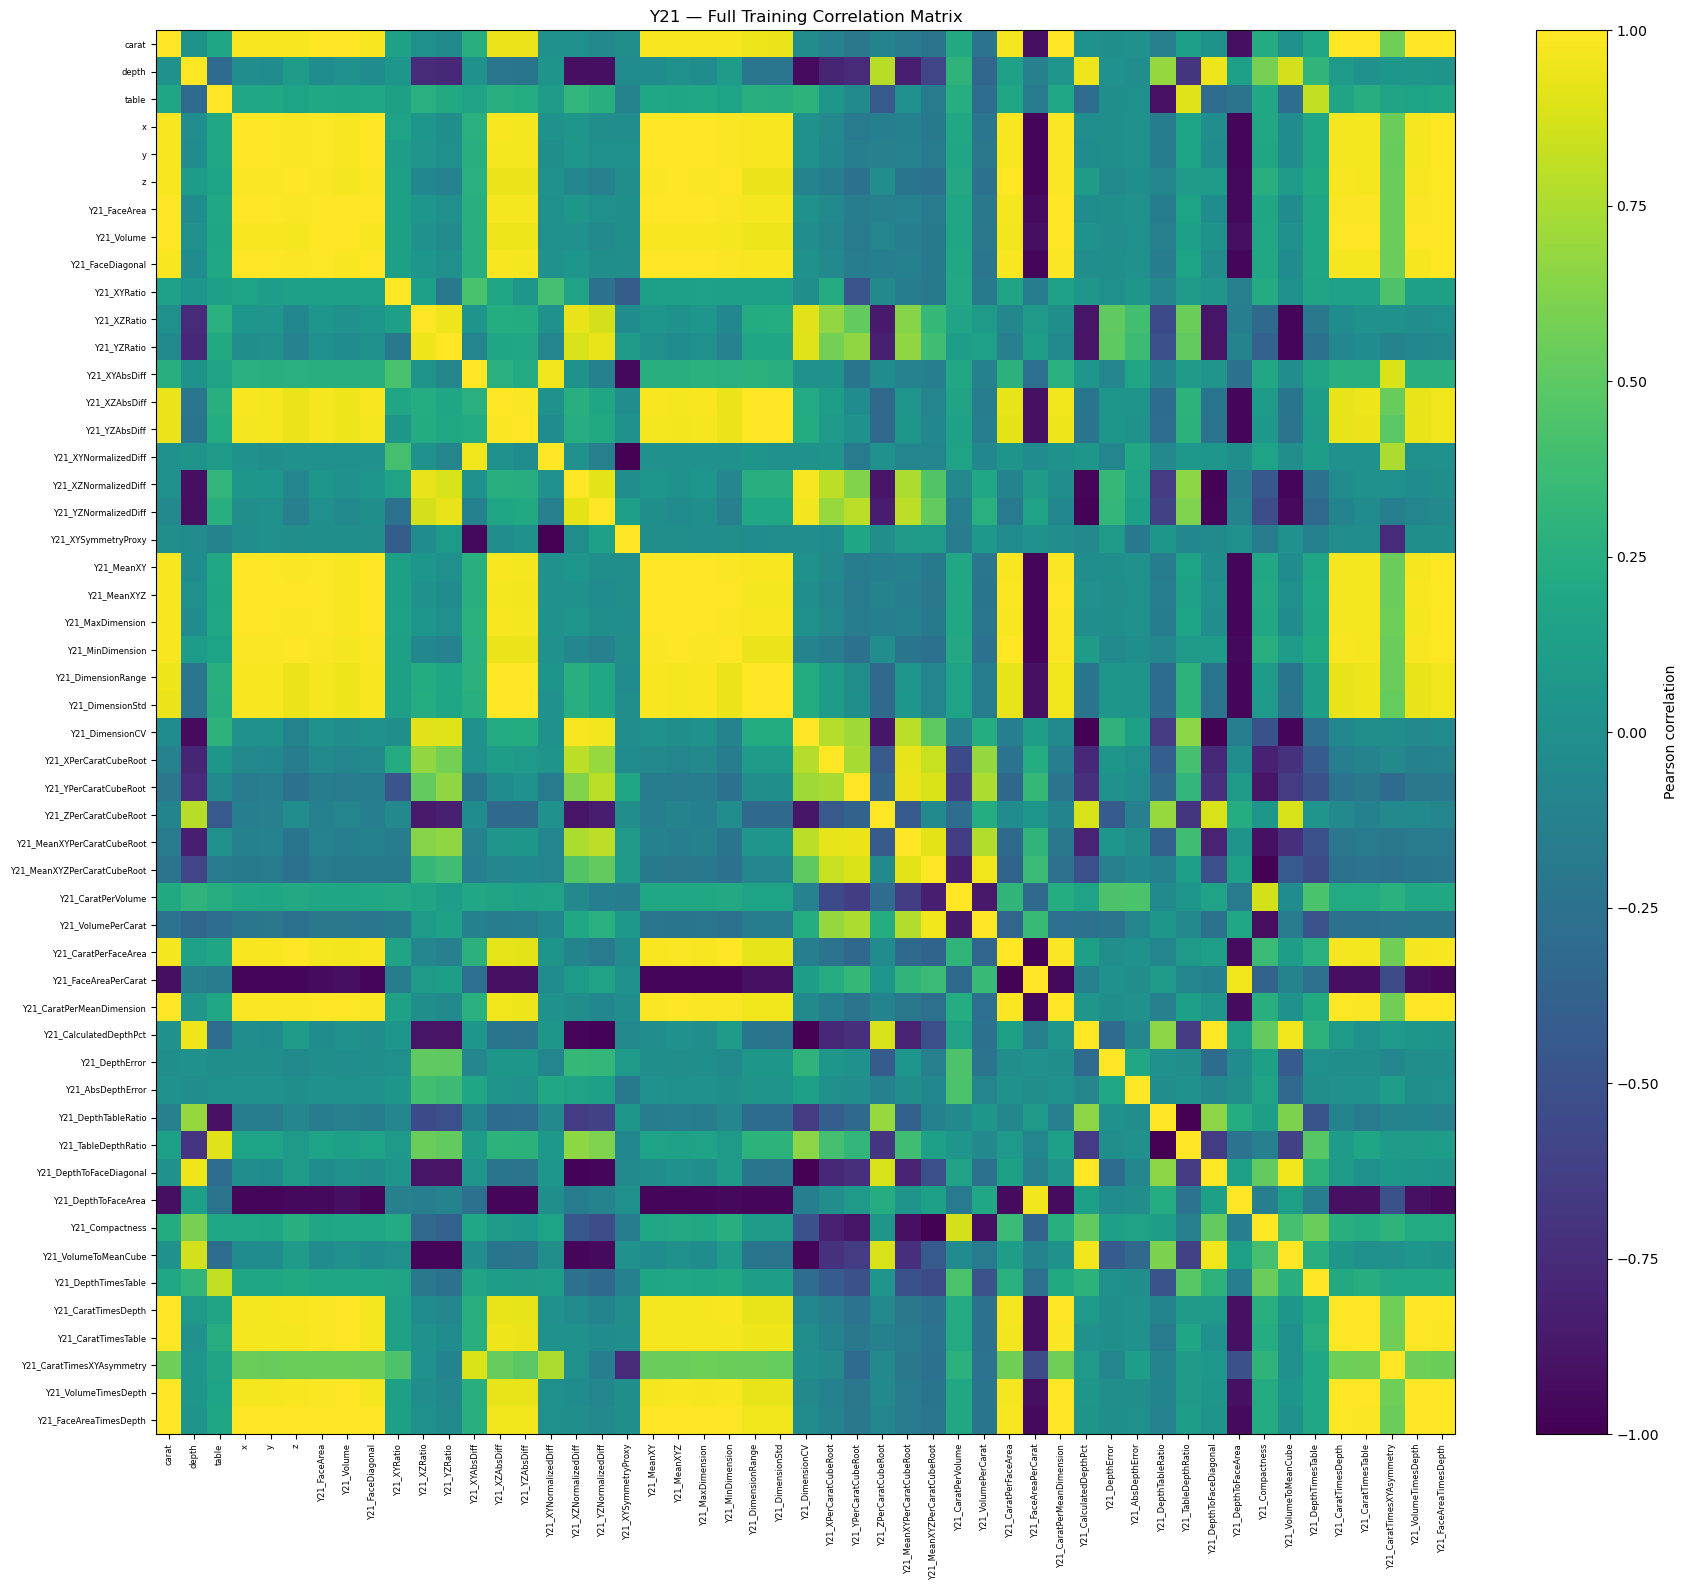

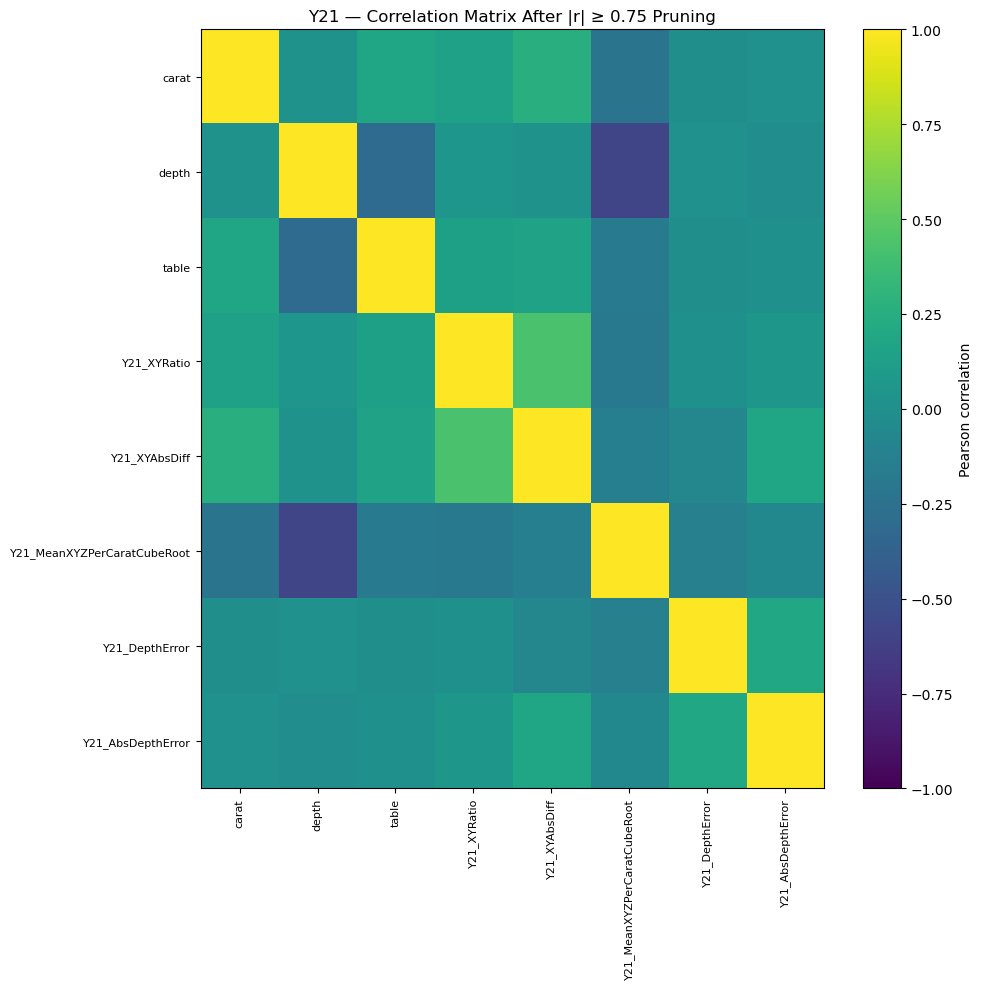



PREPROCESSING
Selected numerical features: 8
Final encoded model inputs: 20
X_train shape: (37744, 20)
X_valid shape: (8088, 20)
X_test shape:  (8088, 20)

✓ Price leakage check passed.


TRAINING Y21 XGBOOST
Best iteration: 1499


Y21 — FINAL RESULTS
   Dataset  Accuracy  Balanced_Accuracy  Macro_Precision  Macro_Recall  Macro_F1  Weighted_F1  Mean_Family_Error  Within_1_Family  Severe_Error
Validation    50.791             47.199           40.897        47.199    42.715       51.217              0.626           88.316        11.684
      Test    50.321             48.049           41.581        48.049    43.389       50.790              0.632           88.365        11.635


Y21 — TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           I     0.3561    0.4234    0.3868       111
          SI     0.6214    0.6104    0.6159      3337
          VS     0.5163    0.3988    0.4500      3064
         VVS     0.3736    0.4847    0.4220      1308
        

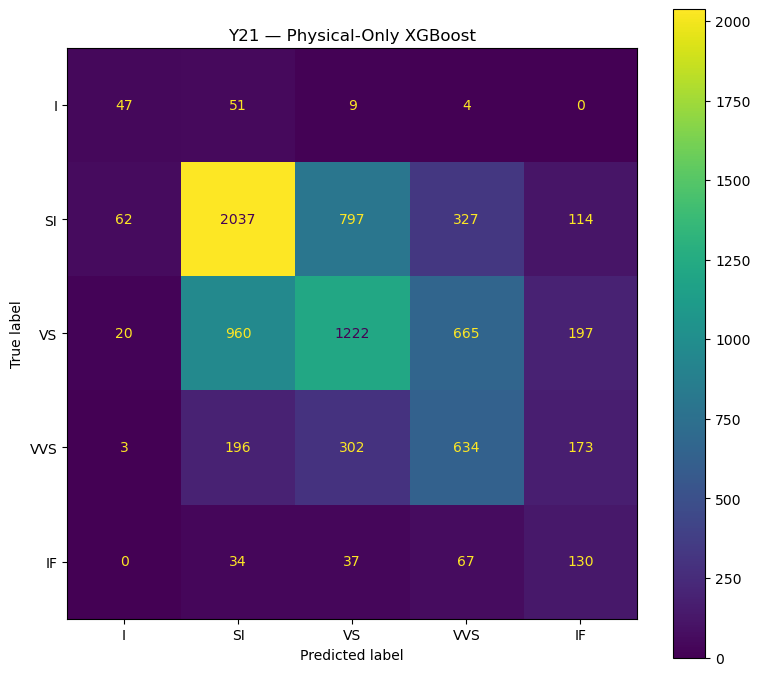



Y21 — TOP 30 MODEL FEATURES
                             Feature  Importance
               categorical__cut_Fair    0.354316
                categorical__color_D    0.065034
              categorical__cut_Ideal    0.062510
                      numeric__carat    0.060942
                categorical__color_E    0.047332
                categorical__color_G    0.038707
                numeric__Y21_XYRatio    0.032561
               categorical__cut_Good    0.029896
                categorical__color_J    0.028802
numeric__Y21_MeanXYZPerCaratCubeRoot    0.028740
          numeric__Y21_AbsDepthError    0.027083
                categorical__color_H    0.026966
            categorical__cut_Premium    0.025956
                      numeric__depth    0.025686
          categorical__cut_Very Good    0.025353
              numeric__Y21_XYAbsDiff    0.024800
                categorical__color_I    0.024459
                categorical__color_F    0.024342
                      numeric__table   

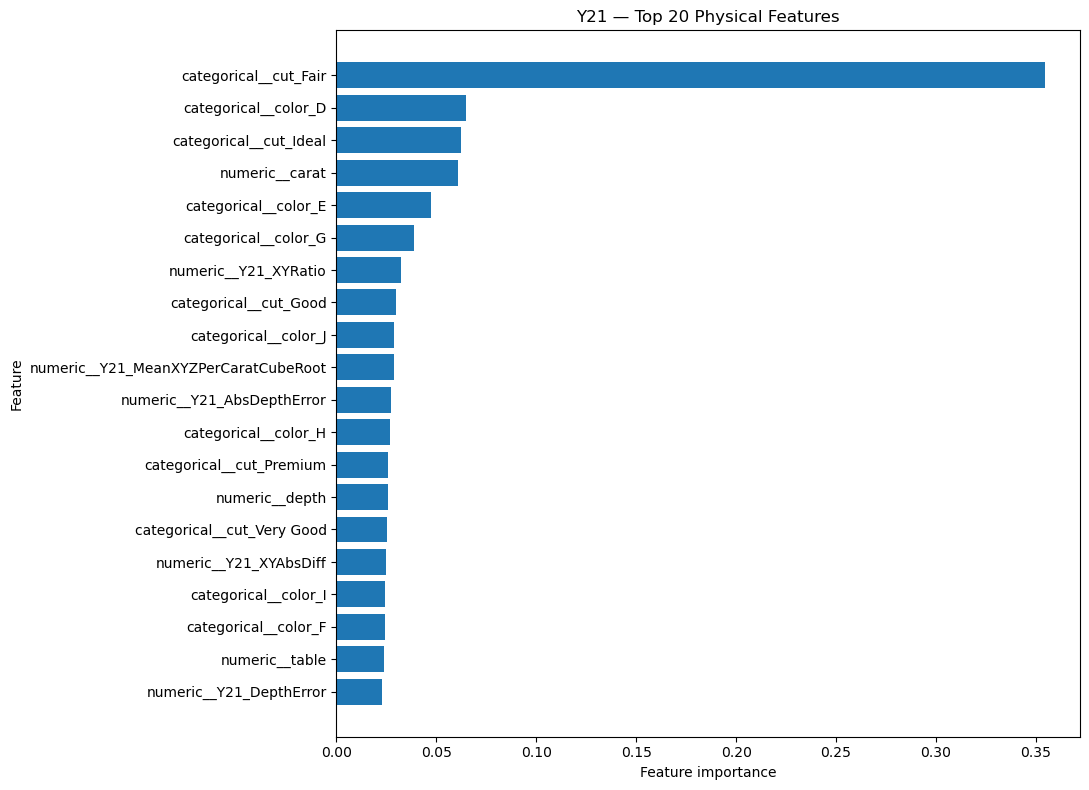



Y21 COMPLETE

DATA
----

Dataset:
    C:\Users\alihu\Projects\ML Course\Diamond\sideEDA\data\cleaned\diamonds_cleaned.csv

Rows used:
    53,920

Price used:
    NO


FEATURE ENGINEERING
-------------------

Candidate numerical features:
    51

Correlation threshold:
    |r| >= 0.75

Features retained:
    8

Features removed:
    43

Largest remaining |correlation|:
    0.5791

Final encoded model inputs:
    20


TEST PERFORMANCE
----------------

Accuracy:
    50.32%

Balanced Accuracy:
    48.05%

Macro Precision:
    41.58%

Macro Recall:
    48.05%

Macro F1:
    43.39%

Weighted F1:
    50.79%

Mean Family Error:
    0.6323

Within ±1 Family:
    88.37%

Severe Error:
    11.63%


SAVED OUTPUTS
-------------

C:\Users\alihu\Projects\ML Course\Diamond\sideEDA\y21_outputs

Important files:

    y21_full_training_correlation_matrix.csv
    y21_high_correlation_pairs.csv
    y21_selected_numeric_features.csv
    y21_dropped_correlated_features.csv
    y21_pruned_correlation_matri

In [9]:
# ==========================================================================================
# Y21 — FINAL PHYSICAL-ONLY DIAMOND CLARITY EXPERIMENT
# ==========================================================================================
#
# DATA:
#   C:\Users\alihu\Projects\ML Course\Diamond\sideEDA\data\cleaned\diamonds_cleaned.csv
#
# PURPOSE:
#   Predict diamond clarity using ONLY physical / geometric information.
#
# PRICE POLICY:
#   Price is deleted immediately.
#   No price-derived feature is allowed anywhere in Y21.
#
# TARGET:
#
#       I  <  SI  <  VS  <  VVS  <  IF
#
# Original grades:
#
#       I1          -> I
#       SI2 / SI1   -> SI
#       VS2 / VS1   -> VS
#       VVS2 / VVS1 -> VVS
#       IF          -> IF
#
# PIPELINE:
#
#   Load cleaned CSV
#        ↓
#   Remove price
#        ↓
#   Validate / clean physical measurements
#        ↓
#   Engineer physical features
#        ↓
#   70 / 15 / 15 stratified split
#        ↓
#   TRAIN ONLY:
#       median imputation
#       Pearson correlation matrix
#       remove features where |r| >= 0.75
#        ↓
#   StandardScaler on remaining numeric features
#        ↓
#   One-hot encode cut + color
#        ↓
#   Balanced XGBoost
#        ↓
#   Validation + test evaluation
#        ↓
#   Feature importance + saved outputs
#
# IMPORTANT:
#
#   Correlation pruning is based on TRAINING DATA ONLY.
#   Scaling is fit on TRAINING DATA ONLY.
#   Test data remains untouched until final evaluation.
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

CORRELATION_THRESHOLD = 0.75

DATA_PATH = Path(
    r"C:\Users\alihu\Projects\ML Course\Diamond\sideEDA\data\cleaned\diamonds_cleaned.csv"
)

OUTPUT_DIR = Path(
    "y21_outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


CLARITY_CLASSES = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


CLARITY_TO_FAMILY = {
    "I1": 0,

    "SI2": 1,
    "SI1": 1,

    "VS2": 2,
    "VS1": 2,

    "VVS2": 3,
    "VVS1": 3,

    "IF": 4,
}


# ==========================================================================================
# 3. LOAD DATA
# ==========================================================================================

if not DATA_PATH.exists():

    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_PATH}"
    )


df = pd.read_csv(
    DATA_PATH
)


# Normalize column names.
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
)


# Remove accidental index columns if they exist.
unnamed_columns = [
    column
    for column in df.columns
    if column.startswith("unnamed:")
]


if unnamed_columns:

    df = df.drop(
        columns=unnamed_columns
    )


print("=" * 130)
print("Y21 — PHYSICAL-ONLY DIAMOND CLARITY EXPERIMENT")
print("=" * 130)

print(
    f"\nDataset:\n{DATA_PATH}"
)

print(
    f"\nRows loaded: {len(df):,}"
)

print(
    f"Columns loaded: {len(df.columns)}"
)

print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)


# ==========================================================================================
# 4. VERIFY REQUIRED DATA
# ==========================================================================================

REQUIRED_COLUMNS = [
    "carat",
    "cut",
    "color",
    "clarity",
    "depth",
    "table",
    "x",
    "y",
    "z",
]


missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in df.columns
]


if missing_columns:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ==========================================================================================
# 5. REMOVE PRICE COMPLETELY
# ==========================================================================================

if "price" in df.columns:

    df = df.drop(
        columns=["price"]
    )


if "price" in df.columns:

    raise RuntimeError(
        "Price was not successfully removed."
    )


print(
    "\n✓ Price removed."
)


# ==========================================================================================
# 6. BASIC CLEANING
# ==========================================================================================

y21_df = df.copy()


rows_before_cleaning = len(
    y21_df
)


# Clean categorical text.
for column in [
    "cut",
    "color",
    "clarity",
]:

    y21_df[column] = (
        y21_df[column]
        .astype(str)
        .str.strip()
    )


# Ensure numerical columns are actually numeric.
NUMERIC_RAW_COLUMNS = [
    "carat",
    "depth",
    "table",
    "x",
    "y",
    "z",
]


for column in NUMERIC_RAW_COLUMNS:

    y21_df[column] = pd.to_numeric(
        y21_df[column],
        errors="coerce",
    )


# Remove missing required information.
y21_df = y21_df.dropna(
    subset=REQUIRED_COLUMNS
).copy()


# Remove physically impossible values.
for column in [
    "carat",
    "depth",
    "table",
    "x",
    "y",
    "z",
]:

    y21_df = y21_df[
        y21_df[column] > 0
    ].copy()


# Remove infinities.
y21_df = y21_df.replace(
    [np.inf, -np.inf],
    np.nan,
)


y21_df = y21_df.reset_index(
    drop=True
)


print("\n")
print("=" * 130)
print("CLEANING")
print("=" * 130)

print(
    f"Rows before cleaning: {rows_before_cleaning:,}"
)

print(
    f"Rows after cleaning:  {len(y21_df):,}"
)

print(
    f"Rows removed:         "
    f"{rows_before_cleaning - len(y21_df):,}"
)


# ==========================================================================================
# 7. ORIGINAL PHYSICAL FEATURES
# ==========================================================================================
#
# Base information:
#
# carat
# depth
# table
# x
# y
# z
# cut
# color
#
# Everything engineered below can be generated from those measurements.
# ==========================================================================================


# ==========================================================================================
# 8. FACE AREA / VOLUME / DIAGONAL
# ==========================================================================================

y21_df["Y21_FaceArea"] = (
    y21_df["x"]
    *
    y21_df["y"]
)


y21_df["Y21_Volume"] = (
    y21_df["x"]
    *
    y21_df["y"]
    *
    y21_df["z"]
)


y21_df["Y21_FaceDiagonal"] = np.sqrt(
    y21_df["x"] ** 2
    +
    y21_df["y"] ** 2
)


# ==========================================================================================
# 9. BASIC SHAPE RATIOS
# ==========================================================================================

y21_df["Y21_XYRatio"] = (
    y21_df["x"]
    /
    y21_df["y"]
)


y21_df["Y21_XZRatio"] = (
    y21_df["x"]
    /
    y21_df["z"]
)


y21_df["Y21_YZRatio"] = (
    y21_df["y"]
    /
    y21_df["z"]
)


# ==========================================================================================
# 10. ABSOLUTE DIMENSION DIFFERENCES
# ==========================================================================================

y21_df["Y21_XYAbsDiff"] = np.abs(
    y21_df["x"]
    -
    y21_df["y"]
)


y21_df["Y21_XZAbsDiff"] = np.abs(
    y21_df["x"]
    -
    y21_df["z"]
)


y21_df["Y21_YZAbsDiff"] = np.abs(
    y21_df["y"]
    -
    y21_df["z"]
)


# ==========================================================================================
# 11. NORMALIZED DIMENSION DIFFERENCES
# ==========================================================================================
#
# These make the differences scale-independent.
#
# Example:
#
# abs(x-y)=0.1 means something different for a tiny diamond
# compared with a very large diamond.
#
# ==========================================================================================

xy_mean = (
    y21_df["x"]
    +
    y21_df["y"]
) / 2.0


xz_mean = (
    y21_df["x"]
    +
    y21_df["z"]
) / 2.0


yz_mean = (
    y21_df["y"]
    +
    y21_df["z"]
) / 2.0


y21_df["Y21_XYNormalizedDiff"] = (
    y21_df["Y21_XYAbsDiff"]
    /
    xy_mean
)


y21_df["Y21_XZNormalizedDiff"] = (
    y21_df["Y21_XZAbsDiff"]
    /
    xz_mean
)


y21_df["Y21_YZNormalizedDiff"] = (
    y21_df["Y21_YZAbsDiff"]
    /
    yz_mean
)


# ==========================================================================================
# 12. XY SYMMETRY PROXY
# ==========================================================================================
#
# IMPORTANT:
#
# This is NOT official gemological symmetry.
#
# It is only an x/y geometric consistency proxy.
#
# Higher ≈ more similar x and y.
# ==========================================================================================

y21_df["Y21_XYSymmetryProxy"] = (
    1.0
    -
    y21_df["Y21_XYNormalizedDiff"]
)


# ==========================================================================================
# 13. DIMENSION SUMMARY FEATURES
# ==========================================================================================

dimension_matrix = y21_df[
    [
        "x",
        "y",
        "z",
    ]
]


y21_df["Y21_MeanXY"] = (
    y21_df["x"]
    +
    y21_df["y"]
) / 2.0


y21_df["Y21_MeanXYZ"] = (
    dimension_matrix.mean(
        axis=1
    )
)


y21_df["Y21_MaxDimension"] = (
    dimension_matrix.max(
        axis=1
    )
)


y21_df["Y21_MinDimension"] = (
    dimension_matrix.min(
        axis=1
    )
)


y21_df["Y21_DimensionRange"] = (
    y21_df["Y21_MaxDimension"]
    -
    y21_df["Y21_MinDimension"]
)


y21_df["Y21_DimensionStd"] = (
    dimension_matrix.std(
        axis=1,
        ddof=0,
    )
)


y21_df["Y21_DimensionCV"] = (
    y21_df["Y21_DimensionStd"]
    /
    y21_df["Y21_MeanXYZ"]
)


# ==========================================================================================
# 14. CARAT-NORMALIZED LINEAR DIMENSIONS
# ==========================================================================================
#
# Linear dimensions approximately scale with cube root of physical volume.
#
# Therefore:
#
# x / carat^(1/3)
#
# asks:
#
# "How large is x relative to this diamond's weight?"
#
# ==========================================================================================

carat_cube_root = np.cbrt(
    y21_df["carat"]
)


y21_df["Y21_XPerCaratCubeRoot"] = (
    y21_df["x"]
    /
    carat_cube_root
)


y21_df["Y21_YPerCaratCubeRoot"] = (
    y21_df["y"]
    /
    carat_cube_root
)


y21_df["Y21_ZPerCaratCubeRoot"] = (
    y21_df["z"]
    /
    carat_cube_root
)


y21_df["Y21_MeanXYPerCaratCubeRoot"] = (
    y21_df["Y21_MeanXY"]
    /
    carat_cube_root
)


y21_df["Y21_MeanXYZPerCaratCubeRoot"] = (
    y21_df["Y21_MeanXYZ"]
    /
    carat_cube_root
)


# ==========================================================================================
# 15. WEIGHT RELATIVE TO SIZE
# ==========================================================================================

y21_df["Y21_CaratPerVolume"] = (
    y21_df["carat"]
    /
    y21_df["Y21_Volume"]
)


y21_df["Y21_VolumePerCarat"] = (
    y21_df["Y21_Volume"]
    /
    y21_df["carat"]
)


y21_df["Y21_CaratPerFaceArea"] = (
    y21_df["carat"]
    /
    y21_df["Y21_FaceArea"]
)


y21_df["Y21_FaceAreaPerCarat"] = (
    y21_df["Y21_FaceArea"]
    /
    y21_df["carat"]
)


y21_df["Y21_CaratPerMeanDimension"] = (
    y21_df["carat"]
    /
    y21_df["Y21_MeanXYZ"]
)


# ==========================================================================================
# 16. DEPTH / TABLE GEOMETRY
# ==========================================================================================

y21_df["Y21_CalculatedDepthPct"] = (
    2.0
    *
    y21_df["z"]
    /
    (
        y21_df["x"]
        +
        y21_df["y"]
    )
    *
    100.0
)


y21_df["Y21_DepthError"] = (
    y21_df["depth"]
    -
    y21_df["Y21_CalculatedDepthPct"]
)


y21_df["Y21_AbsDepthError"] = np.abs(
    y21_df["Y21_DepthError"]
)


y21_df["Y21_DepthTableRatio"] = (
    y21_df["depth"]
    /
    y21_df["table"]
)


y21_df["Y21_TableDepthRatio"] = (
    y21_df["table"]
    /
    y21_df["depth"]
)


y21_df["Y21_DepthToFaceDiagonal"] = (
    y21_df["z"]
    /
    y21_df["Y21_FaceDiagonal"]
)


y21_df["Y21_DepthToFaceArea"] = (
    y21_df["z"]
    /
    y21_df["Y21_FaceArea"]
)


# ==========================================================================================
# 17. COMPACTNESS FEATURES
# ==========================================================================================

y21_df["Y21_Compactness"] = (
    y21_df["carat"]
    /
    (
        y21_df["Y21_MeanXYZ"] ** 3
    )
)


y21_df["Y21_VolumeToMeanCube"] = (
    y21_df["Y21_Volume"]
    /
    (
        y21_df["Y21_MeanXYZ"] ** 3
    )
)


# ==========================================================================================
# 18. INTERACTION FEATURES
# ==========================================================================================

y21_df["Y21_DepthTimesTable"] = (
    y21_df["depth"]
    *
    y21_df["table"]
)


y21_df["Y21_CaratTimesDepth"] = (
    y21_df["carat"]
    *
    y21_df["depth"]
)


y21_df["Y21_CaratTimesTable"] = (
    y21_df["carat"]
    *
    y21_df["table"]
)


y21_df["Y21_CaratTimesXYAsymmetry"] = (
    y21_df["carat"]
    *
    y21_df["Y21_XYNormalizedDiff"]
)


y21_df["Y21_VolumeTimesDepth"] = (
    y21_df["Y21_Volume"]
    *
    y21_df["depth"]
)


y21_df["Y21_FaceAreaTimesDepth"] = (
    y21_df["Y21_FaceArea"]
    *
    y21_df["depth"]
)


# ==========================================================================================
# 19. CLEAN ENGINEERED FEATURES
# ==========================================================================================

y21_df = y21_df.replace(
    [np.inf, -np.inf],
    np.nan,
)


# ==========================================================================================
# 20. CREATE TARGET
# ==========================================================================================

y21_df["Clarity_Family_Target"] = (
    y21_df["clarity"]
    .map(
        CLARITY_TO_FAMILY
    )
)


if y21_df[
    "Clarity_Family_Target"
].isna().any():

    unknown_values = (
        y21_df.loc[
            y21_df[
                "Clarity_Family_Target"
            ].isna(),
            "clarity",
        ]
        .unique()
        .tolist()
    )

    raise ValueError(
        f"Unknown clarity values: {unknown_values}"
    )


y21_df[
    "Clarity_Family_Target"
] = (
    y21_df[
        "Clarity_Family_Target"
    ]
    .astype(int)
)


y = y21_df[
    "Clarity_Family_Target"
].to_numpy()


print("\n")
print("=" * 130)
print("CLARITY FAMILY DISTRIBUTION")
print("=" * 130)


for class_index, class_name in enumerate(
    CLARITY_CLASSES
):

    count = (
        y == class_index
    ).sum()

    percentage = (
        count
        /
        len(y)
        *
        100
    )

    print(
        f"{class_name:5s}: "
        f"{count:6,d} "
        f"({percentage:6.2f}%)"
    )


# ==========================================================================================
# 21. COMPLETE NUMERIC FEATURE LIST
# ==========================================================================================

NUMERIC_FEATURES_ALL = [

    # ------------------------------------------------------------------
    # Original measurements
    # ------------------------------------------------------------------

    "carat",
    "depth",
    "table",

    "x",
    "y",
    "z",


    # ------------------------------------------------------------------
    # Size / volume
    # ------------------------------------------------------------------

    "Y21_FaceArea",
    "Y21_Volume",
    "Y21_FaceDiagonal",


    # ------------------------------------------------------------------
    # Ratios
    # ------------------------------------------------------------------

    "Y21_XYRatio",
    "Y21_XZRatio",
    "Y21_YZRatio",


    # ------------------------------------------------------------------
    # Absolute differences
    # ------------------------------------------------------------------

    "Y21_XYAbsDiff",
    "Y21_XZAbsDiff",
    "Y21_YZAbsDiff",


    # ------------------------------------------------------------------
    # Normalized differences
    # ------------------------------------------------------------------

    "Y21_XYNormalizedDiff",
    "Y21_XZNormalizedDiff",
    "Y21_YZNormalizedDiff",


    # ------------------------------------------------------------------
    # Symmetry proxy
    # ------------------------------------------------------------------

    "Y21_XYSymmetryProxy",


    # ------------------------------------------------------------------
    # Dimension summaries
    # ------------------------------------------------------------------

    "Y21_MeanXY",
    "Y21_MeanXYZ",

    "Y21_MaxDimension",
    "Y21_MinDimension",

    "Y21_DimensionRange",
    "Y21_DimensionStd",
    "Y21_DimensionCV",


    # ------------------------------------------------------------------
    # Carat-normalized dimensions
    # ------------------------------------------------------------------

    "Y21_XPerCaratCubeRoot",
    "Y21_YPerCaratCubeRoot",
    "Y21_ZPerCaratCubeRoot",

    "Y21_MeanXYPerCaratCubeRoot",
    "Y21_MeanXYZPerCaratCubeRoot",


    # ------------------------------------------------------------------
    # Weight vs geometry
    # ------------------------------------------------------------------

    "Y21_CaratPerVolume",
    "Y21_VolumePerCarat",

    "Y21_CaratPerFaceArea",
    "Y21_FaceAreaPerCarat",

    "Y21_CaratPerMeanDimension",


    # ------------------------------------------------------------------
    # Depth / table
    # ------------------------------------------------------------------

    "Y21_CalculatedDepthPct",

    "Y21_DepthError",
    "Y21_AbsDepthError",

    "Y21_DepthTableRatio",
    "Y21_TableDepthRatio",

    "Y21_DepthToFaceDiagonal",
    "Y21_DepthToFaceArea",


    # ------------------------------------------------------------------
    # Compactness
    # ------------------------------------------------------------------

    "Y21_Compactness",
    "Y21_VolumeToMeanCube",


    # ------------------------------------------------------------------
    # Interaction features
    # ------------------------------------------------------------------

    "Y21_DepthTimesTable",

    "Y21_CaratTimesDepth",
    "Y21_CaratTimesTable",

    "Y21_CaratTimesXYAsymmetry",

    "Y21_VolumeTimesDepth",
    "Y21_FaceAreaTimesDepth",
]


CATEGORICAL_FEATURES = [
    "cut",
    "color",
]


# ==========================================================================================
# 22. PRICE LEAKAGE SAFETY CHECK
# ==========================================================================================

for feature in (
    NUMERIC_FEATURES_ALL
    +
    CATEGORICAL_FEATURES
):

    if "price" in feature.lower():

        raise RuntimeError(
            f"PRICE LEAKAGE DETECTED: {feature}"
        )


print(
    f"\nCandidate numeric features: "
    f"{len(NUMERIC_FEATURES_ALL)}"
)


# ==========================================================================================
# 23. MODEL DATAFRAME
# ==========================================================================================

ALL_FEATURES = (
    NUMERIC_FEATURES_ALL
    +
    CATEGORICAL_FEATURES
)


X = y21_df[
    ALL_FEATURES
].copy()


# ==========================================================================================
# 24. 70 / 15 / 15 STRATIFIED SPLIT
# ==========================================================================================

indices = np.arange(
    len(y21_df)
)


train_idx, temp_idx = train_test_split(

    indices,

    test_size=0.30,

    random_state=RANDOM_STATE,

    stratify=y,
)


valid_idx, test_idx = train_test_split(

    temp_idx,

    test_size=0.50,

    random_state=RANDOM_STATE,

    stratify=y[
        temp_idx
    ],
)


y_train = y[
    train_idx
]


y_valid = y[
    valid_idx
]


y_test = y[
    test_idx
]


print("\n")
print("=" * 130)
print("DATA SPLIT")
print("=" * 130)


print(
    f"Training:   {len(train_idx):,}"
)

print(
    f"Validation: {len(valid_idx):,}"
)

print(
    f"Testing:    {len(test_idx):,}"
)


# ==========================================================================================
# 25. TRAINING-ONLY MEDIAN IMPUTATION
# ==========================================================================================

training_medians = (

    X.iloc[
        train_idx
    ][
        NUMERIC_FEATURES_ALL
    ]

    .median()
)


X.loc[
    :,
    NUMERIC_FEATURES_ALL
] = (

    X[
        NUMERIC_FEATURES_ALL
    ]

    .fillna(
        training_medians
    )
)


# ==========================================================================================
# 26. TRAINING-ONLY PEARSON CORRELATION MATRIX
# ==========================================================================================
#
# We use absolute correlation:
#
#     r >= +0.75  -> redundant
#
# OR
#
#     r <= -0.75  -> redundant
#
# Equivalent:
#
#     abs(r) >= 0.75
#
# ==========================================================================================

training_numeric = (

    X.iloc[
        train_idx
    ][
        NUMERIC_FEATURES_ALL
    ]

    .copy()
)


correlation_matrix = (

    training_numeric

    .corr(
        method="pearson"
    )
)


correlation_matrix.to_csv(

    OUTPUT_DIR
    /
    "y21_full_training_correlation_matrix.csv"
)


print("\n")
print("=" * 130)
print("CORRELATION ANALYSIS")
print("=" * 130)


print(
    f"Threshold: |r| >= "
    f"{CORRELATION_THRESHOLD:.2f}"
)


# ==========================================================================================
# 27. IDENTIFY HIGHLY CORRELATED PAIRS
# ==========================================================================================

high_correlation_pairs = []


columns = (
    correlation_matrix.columns
)


for i in range(
    len(columns)
):

    for j in range(
        i + 1,
        len(columns)
    ):

        feature_a = columns[i]

        feature_b = columns[j]

        correlation = (
            correlation_matrix.loc[
                feature_a,
                feature_b,
            ]
        )


        if (
            pd.notna(correlation)
            and
            abs(correlation)
            >=
            CORRELATION_THRESHOLD
        ):

            high_correlation_pairs.append(
                {
                    "Feature_A":
                        feature_a,

                    "Feature_B":
                        feature_b,

                    "Correlation":
                        correlation,

                    "Absolute_Correlation":
                        abs(
                            correlation
                        ),
                }
            )


high_correlation_df = pd.DataFrame(
    high_correlation_pairs
)


if not high_correlation_df.empty:

    high_correlation_df = (

        high_correlation_df

        .sort_values(
            "Absolute_Correlation",
            ascending=False,
        )

        .reset_index(
            drop=True
        )
    )


high_correlation_df.to_csv(

    OUTPUT_DIR
    /
    "y21_high_correlation_pairs.csv",

    index=False,
)


print(
    f"\nHighly correlated pairs: "
    f"{len(high_correlation_df):,}"
)


if not high_correlation_df.empty:

    print(
        "\nTOP 40 HIGHLY CORRELATED PAIRS"
    )


    print(

        high_correlation_df

        .head(
            40
        )

        .round(
            4
        )

        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 28. CORRELATION PRUNING
# ==========================================================================================
#
# Greedy algorithm:
#
# 1. Move through feature list in order.
# 2. Keep a feature if it is not strongly correlated with an already-kept feature.
# 3. Drop it if abs(r) >= 0.75 with something already retained.
#
# This produces a deterministic reduced feature set.
# ==========================================================================================

selected_numeric_features = []

dropped_numeric_features = []


for candidate_feature in NUMERIC_FEATURES_ALL:

    correlations_with_kept = []


    for kept_feature in selected_numeric_features:

        correlation = (
            correlation_matrix.loc[
                candidate_feature,
                kept_feature,
            ]
        )


        if pd.notna(
            correlation
        ):

            correlations_with_kept.append(
                (
                    kept_feature,
                    correlation,
                )
            )


    problematic_correlations = [
        (
            kept_feature,
            correlation,
        )

        for (
            kept_feature,
            correlation
        )
        in correlations_with_kept

        if abs(
            correlation
        )
        >=
        CORRELATION_THRESHOLD
    ]


    if problematic_correlations:

        strongest_feature, strongest_corr = max(

            problematic_correlations,

            key=lambda pair: abs(
                pair[1]
            ),
        )


        dropped_numeric_features.append(
            {
                "Dropped_Feature":
                    candidate_feature,

                "Kept_Feature":
                    strongest_feature,

                "Correlation":
                    strongest_corr,

                "Absolute_Correlation":
                    abs(
                        strongest_corr
                    ),
            }
        )


    else:

        selected_numeric_features.append(
            candidate_feature
        )


dropped_features_df = pd.DataFrame(
    dropped_numeric_features
)


selected_features_df = pd.DataFrame(
    {
        "Selected_Feature":
            selected_numeric_features
    }
)


selected_features_df.to_csv(

    OUTPUT_DIR
    /
    "y21_selected_numeric_features.csv",

    index=False,
)


dropped_features_df.to_csv(

    OUTPUT_DIR
    /
    "y21_dropped_correlated_features.csv",

    index=False,
)


print("\n")
print("=" * 130)
print("CORRELATION PRUNING RESULTS")
print("=" * 130)


print(
    f"Numeric features before pruning: "
    f"{len(NUMERIC_FEATURES_ALL)}"
)


print(
    f"Numeric features retained:       "
    f"{len(selected_numeric_features)}"
)


print(
    f"Numeric features removed:        "
    f"{len(dropped_numeric_features)}"
)


print(
    "\nSURVIVING FEATURES"
)


for feature in selected_numeric_features:

    print(
        f"  + {feature}"
    )


print(
    "\nREMOVED CORRELATED FEATURES"
)


if dropped_features_df.empty:

    print(
        "  None"
    )


else:

    print(

        dropped_features_df

        .round(
            4
        )

        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 29. VERIFY PRUNING
# ==========================================================================================
#
# After pruning, there should be no remaining off-diagonal feature pair
# with |r| >= 0.75.
# ==========================================================================================

pruned_correlation_matrix = (

    training_numeric[
        selected_numeric_features
    ]

    .corr(
        method="pearson"
    )
)


pruned_correlation_matrix.to_csv(

    OUTPUT_DIR
    /
    "y21_pruned_correlation_matrix.csv"
)


upper_triangle = (

    pruned_correlation_matrix

    .where(

        np.triu(

            np.ones(
                pruned_correlation_matrix.shape
            ),

            k=1,

        ).astype(bool)
    )
)


remaining_max_absolute_correlation = (

    upper_triangle

    .abs()

    .max()

    .max()
)


print(
    f"\nLargest remaining absolute "
    f"feature correlation: "
    f"{remaining_max_absolute_correlation:.4f}"
)


# ==========================================================================================
# 30. PLOT FULL CORRELATION MATRIX
# ==========================================================================================

fig, ax = plt.subplots(
    figsize=(
        18,
        16,
    )
)


image = ax.imshow(

    correlation_matrix.values,

    vmin=-1,

    vmax=1,

    aspect="auto",
)


ax.set_xticks(
    np.arange(
        len(
            correlation_matrix.columns
        )
    )
)


ax.set_yticks(
    np.arange(
        len(
            correlation_matrix.columns
        )
    )
)


ax.set_xticklabels(

    correlation_matrix.columns,

    rotation=90,

    fontsize=6,
)


ax.set_yticklabels(

    correlation_matrix.columns,

    fontsize=6,
)


ax.set_title(
    "Y21 — Full Training Correlation Matrix"
)


fig.colorbar(

    image,

    ax=ax,

    label="Pearson correlation",
)


fig.tight_layout()


fig.savefig(

    OUTPUT_DIR
    /
    "y21_full_correlation_matrix.png",

    dpi=200,

    bbox_inches="tight",
)


plt.show()


# ==========================================================================================
# 31. PLOT PRUNED CORRELATION MATRIX
# ==========================================================================================

matrix_size = max(

    10,

    len(
        selected_numeric_features
    )
    *
    0.60,
)


fig, ax = plt.subplots(
    figsize=(
        matrix_size,
        matrix_size,
    )
)


image = ax.imshow(

    pruned_correlation_matrix.values,

    vmin=-1,

    vmax=1,

    aspect="auto",
)


ax.set_xticks(

    np.arange(
        len(
            selected_numeric_features
        )
    )
)


ax.set_yticks(

    np.arange(
        len(
            selected_numeric_features
        )
    )
)


ax.set_xticklabels(

    selected_numeric_features,

    rotation=90,

    fontsize=8,
)


ax.set_yticklabels(

    selected_numeric_features,

    fontsize=8,
)


ax.set_title(
    "Y21 — Correlation Matrix After |r| ≥ 0.75 Pruning"
)


fig.colorbar(

    image,

    ax=ax,

    label="Pearson correlation",
)


fig.tight_layout()


fig.savefig(

    OUTPUT_DIR
    /
    "y21_pruned_correlation_matrix.png",

    dpi=200,

    bbox_inches="tight",
)


plt.show()


# ==========================================================================================
# 32. VERSION-SAFE ONE-HOT ENCODER
# ==========================================================================================

try:

    categorical_encoder = OneHotEncoder(

        handle_unknown="ignore",

        sparse_output=False,
    )


except TypeError:

    # Older scikit-learn versions.

    categorical_encoder = OneHotEncoder(

        handle_unknown="ignore",

        sparse=False,
    )


# ==========================================================================================
# 33. PREPROCESSING PIPELINE
# ==========================================================================================
#
# NUMERIC:
#     StandardScaler
#
# CATEGORICAL:
#     OneHotEncoder
#
# Everything is FIT on TRAIN only.
# ==========================================================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",

            StandardScaler(),

            selected_numeric_features,
        ),


        (
            "categorical",

            categorical_encoder,

            CATEGORICAL_FEATURES,
        ),
    ],

    remainder="drop",
)


# ==========================================================================================
# 34. FIT / TRANSFORM
# ==========================================================================================

X_train = (

    preprocessor

    .fit_transform(

        X.iloc[
            train_idx
        ]
    )

    .astype(
        np.float32
    )
)


X_valid = (

    preprocessor

    .transform(

        X.iloc[
            valid_idx
        ]
    )

    .astype(
        np.float32
    )
)


X_test = (

    preprocessor

    .transform(

        X.iloc[
            test_idx
        ]
    )

    .astype(
        np.float32
    )
)


feature_names = (

    preprocessor

    .get_feature_names_out()
)


print("\n")
print("=" * 130)
print("PREPROCESSING")
print("=" * 130)


print(
    f"Selected numerical features: "
    f"{len(selected_numeric_features)}"
)


print(
    f"Final encoded model inputs: "
    f"{X_train.shape[1]}"
)


print(
    f"X_train shape: {X_train.shape}"
)

print(
    f"X_valid shape: {X_valid.shape}"
)

print(
    f"X_test shape:  {X_test.shape}"
)


# ==========================================================================================
# 35. FINAL PRICE LEAKAGE CHECK
# ==========================================================================================

price_features_found = [

    feature

    for feature in feature_names

    if "price" in str(
        feature
    ).lower()
]


if price_features_found:

    raise RuntimeError(
        f"PRICE LEAKAGE FOUND: "
        f"{price_features_found}"
    )


print(
    "\n✓ Price leakage check passed."
)


# ==========================================================================================
# 36. CLASS BALANCING
# ==========================================================================================

training_sample_weights = (

    compute_sample_weight(

        class_weight="balanced",

        y=y_train,
    )
)


# ==========================================================================================
# 37. XGBOOST
# ==========================================================================================
#
# NOTE:
#
# Tree models technically do not require StandardScaler.
#
# We are scaling anyway because:
#
# 1. You requested a standardized preprocessing pipeline.
# 2. It makes this exact feature representation reusable later for:
#       - ANN
#       - Logistic Regression
#       - SVM
#       - KNN
#
# ==========================================================================================

model = XGBClassifier(

    objective="multi:softprob",

    num_class=len(
        CLARITY_CLASSES
    ),

    eval_metric="mlogloss",

    n_estimators=1500,

    learning_rate=0.03,

    max_depth=6,

    min_child_weight=2,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_alpha=0.10,

    reg_lambda=1.0,

    tree_method="hist",

    random_state=RANDOM_STATE,

    n_jobs=-1,

    early_stopping_rounds=75,
)


print("\n")
print("=" * 130)
print("TRAINING Y21 XGBOOST")
print("=" * 130)


model.fit(

    X_train,

    y_train,

    sample_weight=training_sample_weights,

    eval_set=[
        (
            X_valid,
            y_valid,
        )
    ],

    verbose=False,
)


if hasattr(
    model,
    "best_iteration"
):

    print(
        f"Best iteration: "
        f"{model.best_iteration}"
    )


# ==========================================================================================
# 38. METRIC FUNCTION
# ==========================================================================================

def calculate_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dataset_name: str,
) -> dict:

    family_distance = np.abs(
        y_true
        -
        y_pred
    )


    return {

        "Dataset":
            dataset_name,


        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,


        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,


        "Macro_Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,


        "Macro_Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,


        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,


        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,


        "Mean_Family_Error":
            family_distance.mean(),


        "Within_1_Family":
            (
                family_distance
                <=
                1
            ).mean()
            *
            100,


        "Severe_Error":
            (
                family_distance
                >
                1
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 39. VALIDATION PREDICTIONS
# ==========================================================================================

validation_predictions = (

    model.predict(
        X_valid
    )
)


validation_metrics = (

    calculate_metrics(

        y_valid,

        validation_predictions,

        "Validation",
    )
)


# ==========================================================================================
# 40. FINAL TEST PREDICTIONS
# ==========================================================================================

test_predictions = (

    model.predict(
        X_test
    )
)


test_metrics = (

    calculate_metrics(

        y_test,

        test_predictions,

        "Test",
    )
)


# ==========================================================================================
# 41. RESULTS TABLE
# ==========================================================================================

results_df = pd.DataFrame(
    [
        validation_metrics,
        test_metrics,
    ]
)


print("\n")
print("=" * 145)
print("Y21 — FINAL RESULTS")
print("=" * 145)


print(

    results_df

    .round(
        3
    )

    .to_string(
        index=False
    )
)


results_df.to_csv(

    OUTPUT_DIR
    /
    "y21_metrics.csv",

    index=False,
)


# ==========================================================================================
# 42. CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 130)
print("Y21 — TEST CLASSIFICATION REPORT")
print("=" * 130)


print(

    classification_report(

        y_test,

        test_predictions,

        labels=np.arange(
            len(
                CLARITY_CLASSES
            )
        ),

        target_names=(
            CLARITY_CLASSES
        ),

        digits=4,

        zero_division=0,
    )
)


# ==========================================================================================
# 43. CONFUSION MATRIX — RAW COUNTS
# ==========================================================================================

confusion = confusion_matrix(

    y_test,

    test_predictions,

    labels=np.arange(
        len(
            CLARITY_CLASSES
        )
    ),
)


confusion_df = pd.DataFrame(

    confusion,

    index=[
        f"Actual_{name}"
        for name in CLARITY_CLASSES
    ],

    columns=[
        f"Pred_{name}"
        for name in CLARITY_CLASSES
    ],
)


print("\n")
print("=" * 130)
print("CONFUSION MATRIX — COUNTS")
print("=" * 130)


print(
    confusion_df.to_string()
)


confusion_df.to_csv(

    OUTPUT_DIR
    /
    "y21_confusion_matrix_counts.csv"
)


# ==========================================================================================
# 44. CONFUSION MATRIX — ROW PERCENTAGES
# ==========================================================================================

confusion_percent = (

    confusion

    /

    np.maximum(

        confusion.sum(
            axis=1,
            keepdims=True,
        ),

        1,
    )

    *
    100
)


confusion_percent_df = pd.DataFrame(

    confusion_percent,

    index=[
        f"Actual_{name}"
        for name in CLARITY_CLASSES
    ],

    columns=[
        f"Pred_{name}"
        for name in CLARITY_CLASSES
    ],
)


print("\n")
print("=" * 130)
print("CONFUSION MATRIX — ROW %")
print("=" * 130)


print(

    confusion_percent_df

    .round(
        2
    )

    .to_string()
)


confusion_percent_df.to_csv(

    OUTPUT_DIR
    /
    "y21_confusion_matrix_percent.csv"
)


# ==========================================================================================
# 45. CONFUSION MATRIX PLOT
# ==========================================================================================

fig, ax = plt.subplots(
    figsize=(
        8,
        7,
    )
)


display = ConfusionMatrixDisplay(

    confusion_matrix=confusion,

    display_labels=CLARITY_CLASSES,
)


display.plot(
    ax=ax,
    values_format="d",
)


ax.set_title(
    "Y21 — Physical-Only XGBoost"
)


fig.tight_layout()


fig.savefig(

    OUTPUT_DIR
    /
    "y21_confusion_matrix.png",

    dpi=200,

    bbox_inches="tight",
)


plt.show()


# ==========================================================================================
# 46. XGBOOST FEATURE IMPORTANCE
# ==========================================================================================

importance_df = pd.DataFrame(

    {

        "Feature":
            feature_names,

        "Importance":
            model.feature_importances_,
    }
)


importance_df = (

    importance_df

    .sort_values(
        "Importance",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 130)
print("Y21 — TOP 30 MODEL FEATURES")
print("=" * 130)


print(

    importance_df

    .head(
        30
    )

    .round(
        6
    )

    .to_string(
        index=False
    )
)


importance_df.to_csv(

    OUTPUT_DIR
    /
    "y21_feature_importance.csv",

    index=False,
)


# ==========================================================================================
# 47. FEATURE IMPORTANCE PLOT
# ==========================================================================================

top_20_features = (

    importance_df

    .head(
        20
    )

    .sort_values(
        "Importance",
        ascending=True,
    )
)


fig, ax = plt.subplots(
    figsize=(
        11,
        8,
    )
)


ax.barh(

    top_20_features[
        "Feature"
    ],

    top_20_features[
        "Importance"
    ],
)


ax.set_xlabel(
    "Feature importance"
)


ax.set_ylabel(
    "Feature"
)


ax.set_title(
    "Y21 — Top 20 Physical Features"
)


fig.tight_layout()


fig.savefig(

    OUTPUT_DIR
    /
    "y21_top20_feature_importance.png",

    dpi=200,

    bbox_inches="tight",
)


plt.show()


# ==========================================================================================
# 48. SAVE FINAL MODEL INPUT FEATURE NAMES
# ==========================================================================================

pd.DataFrame(
    {
        "Final_Model_Feature":
            feature_names
    }
).to_csv(

    OUTPUT_DIR
    /
    "y21_final_encoded_features.csv",

    index=False,
)


# ==========================================================================================
# 49. SAVE TEST PREDICTIONS
# ==========================================================================================

prediction_df = pd.DataFrame(
    {
        "Actual_Class":
            [
                CLARITY_CLASSES[
                    value
                ]
                for value in y_test
            ],

        "Predicted_Class":
            [
                CLARITY_CLASSES[
                    value
                ]
                for value in test_predictions
            ],

        "Actual_Code":
            y_test,

        "Predicted_Code":
            test_predictions,

        "Family_Error":
            np.abs(
                y_test
                -
                test_predictions
            ),
    }
)


prediction_df.to_csv(

    OUTPUT_DIR
    /
    "y21_test_predictions.csv",

    index=False,
)


# ==========================================================================================
# 50. FINAL INTEGRITY CHECK
# ==========================================================================================

assert "price" not in y21_df.columns

assert all(
    "price" not in str(
        feature
    ).lower()

    for feature in feature_names
)


# ==========================================================================================
# 51. FINAL SUMMARY
# ==========================================================================================

print("\n")
print("=" * 145)
print("Y21 COMPLETE")
print("=" * 145)


print(
    f"""
DATA
----

Dataset:
    {DATA_PATH}

Rows used:
    {len(y21_df):,}

Price used:
    NO


FEATURE ENGINEERING
-------------------

Candidate numerical features:
    {len(NUMERIC_FEATURES_ALL)}

Correlation threshold:
    |r| >= {CORRELATION_THRESHOLD:.2f}

Features retained:
    {len(selected_numeric_features)}

Features removed:
    {len(dropped_numeric_features)}

Largest remaining |correlation|:
    {remaining_max_absolute_correlation:.4f}

Final encoded model inputs:
    {X_train.shape[1]}


TEST PERFORMANCE
----------------

Accuracy:
    {test_metrics['Accuracy']:.2f}%

Balanced Accuracy:
    {test_metrics['Balanced_Accuracy']:.2f}%

Macro Precision:
    {test_metrics['Macro_Precision']:.2f}%

Macro Recall:
    {test_metrics['Macro_Recall']:.2f}%

Macro F1:
    {test_metrics['Macro_F1']:.2f}%

Weighted F1:
    {test_metrics['Weighted_F1']:.2f}%

Mean Family Error:
    {test_metrics['Mean_Family_Error']:.4f}

Within ±1 Family:
    {test_metrics['Within_1_Family']:.2f}%

Severe Error:
    {test_metrics['Severe_Error']:.2f}%


SAVED OUTPUTS
-------------

{OUTPUT_DIR.resolve()}

Important files:

    y21_full_training_correlation_matrix.csv
    y21_high_correlation_pairs.csv
    y21_selected_numeric_features.csv
    y21_dropped_correlated_features.csv
    y21_pruned_correlation_matrix.csv
    y21_metrics.csv
    y21_feature_importance.csv
    y21_confusion_matrix_percent.csv
    y21_test_predictions.csv
"""
)

Y22 — MI-GUIDED PHYSICAL CLARITY MODEL

Dataset:
C:\Users\alihu\Projects\ML Course\Diamond\sideEDA\data\cleaned\diamonds_cleaned.csv

Rows loaded: 53,920
Columns loaded: 10

Columns:
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

✓ Price removed.


CLEANING
Rows before: 53,920
Rows after:  53,920
Removed:     0


CLARITY FAMILY DISTRIBUTION
I    :    738 (  1.37%)
SI   : 22,248 ( 41.26%)
VS   : 20,424 ( 37.88%)
VVS  :  8,720 ( 16.17%)
IF   :  1,790 (  3.32%)

Candidate numeric features: 51


DATA SPLIT
Training:   37,744
Validation: 8,088
Testing:    8,088


MUTUAL INFORMATION RANKING
 MI_Rank                     Feature  Mutual_Information
       1      Y22_FaceAreaTimesDepth            0.164536
       2                  Y22_Volume            0.164100
       3        Y22_VolumeTimesDepth            0.162432
       4        Y22_FaceAreaPerCarat            0.150176
       5        Y22_CaratPerFaceArea            0.146582
       6         Y22_DepthToFaceA

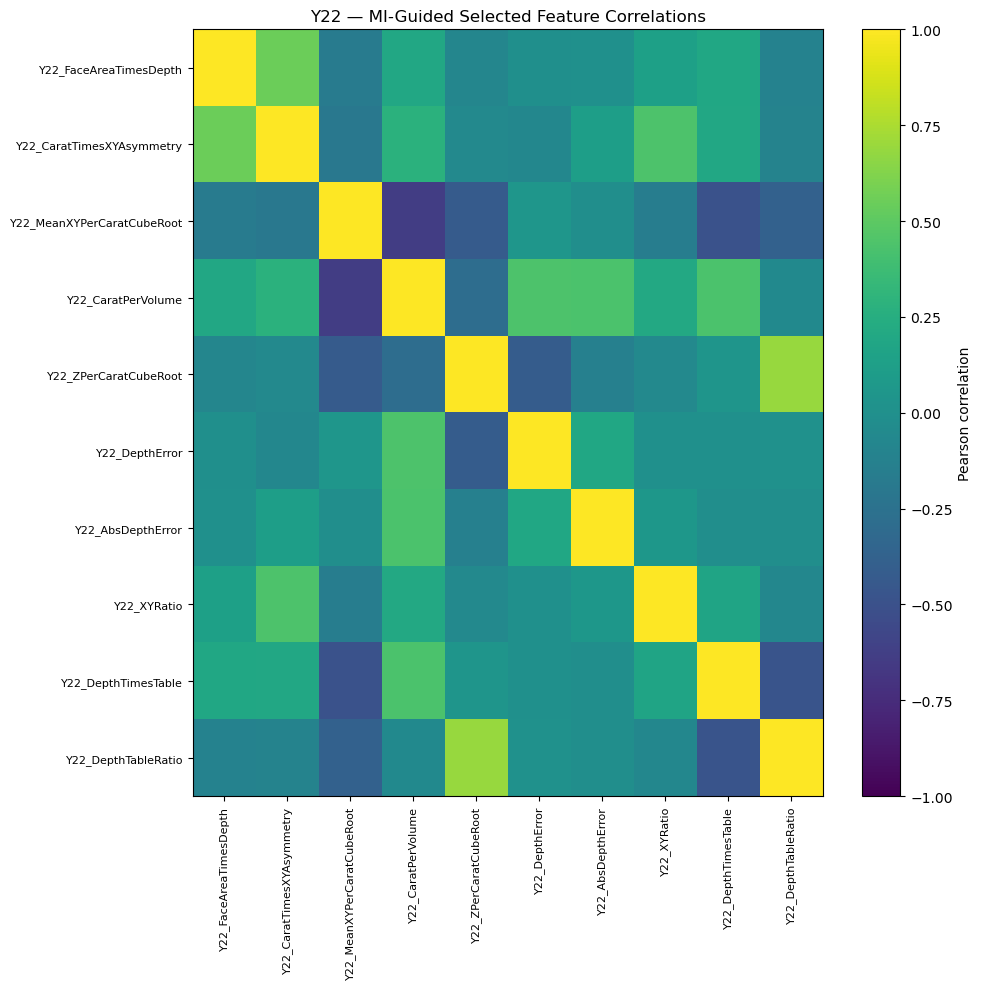

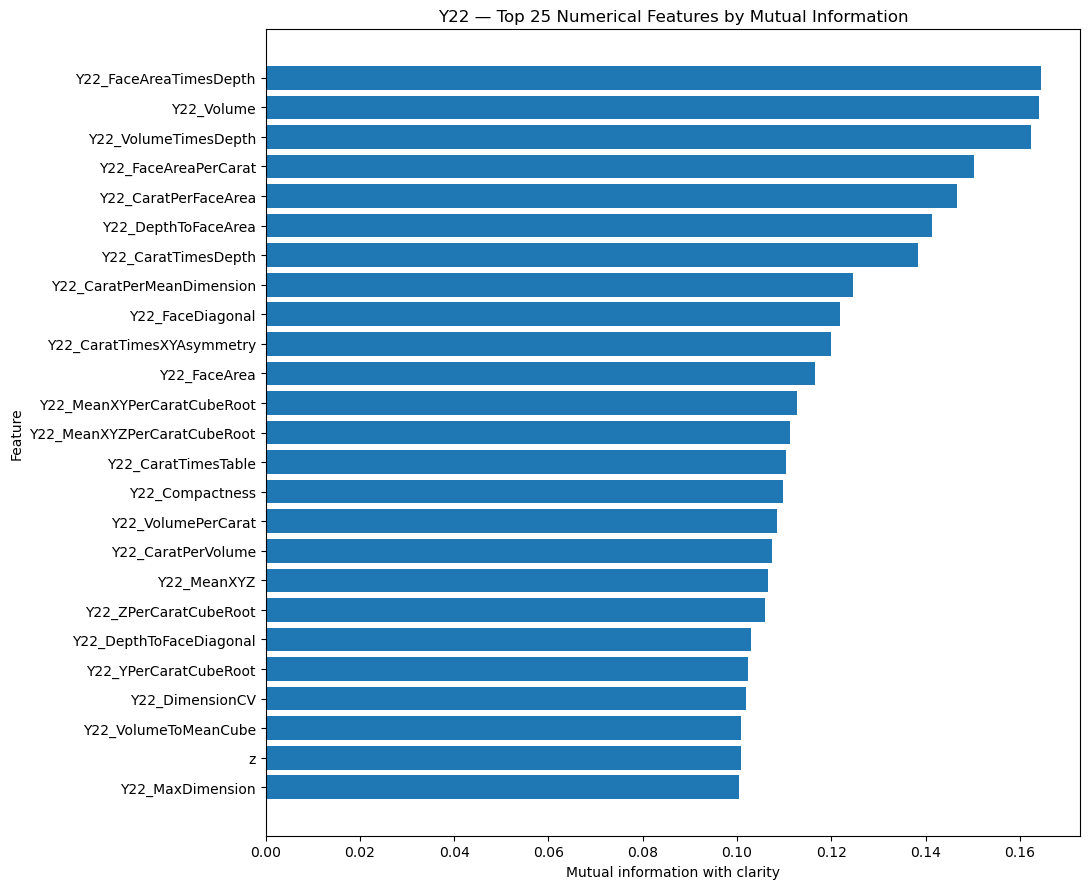



FINAL MODEL INPUT
Selected numerical perspectives: 10
Encoded model inputs: 22
X_train: (37744, 22)
X_valid: (8088, 22)
X_test:  (8088, 22)

✓ Price leakage check passed.


TRAINING Y22
Best iteration: 2999


Y22 — FINAL RESULTS
   Dataset  Accuracy  Balanced_Accuracy  Macro_Precision  Macro_Recall  Macro_F1  Weighted_F1  Mean_Family_Error  Within_1_Family  Severe_Error
Validation    54.797             48.278           49.127        48.278    48.288       54.800              0.550           91.222         8.778
      Test    54.377             46.716           47.455        46.716    46.730       54.458              0.557           91.086         8.914


TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           I     0.4938    0.3604    0.4167       111
          SI     0.6288    0.6377    0.6332      3337
          VS     0.5322    0.4856    0.5078      3064
         VVS     0.4338    0.4939    0.4619      1308
          IF     0.2840    0.3582    

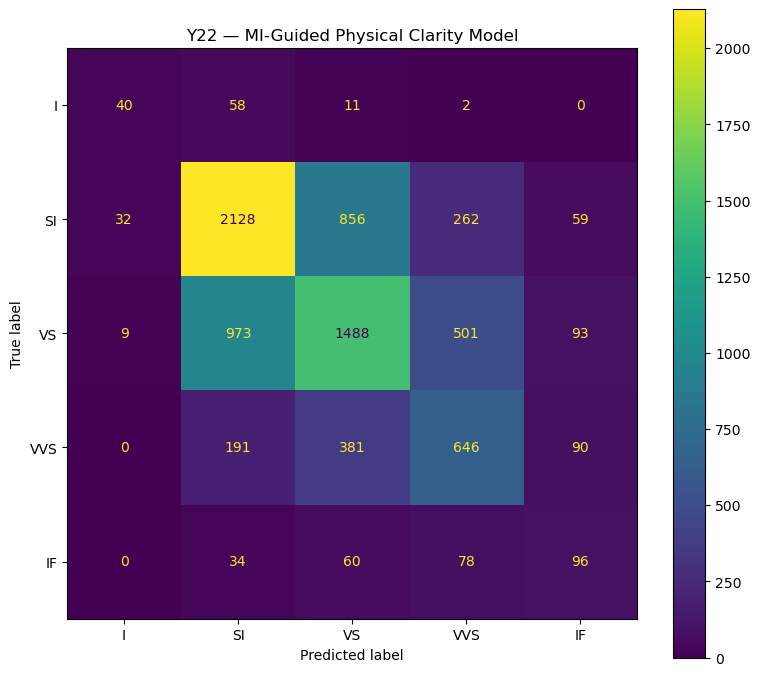



Y22 — TOP 30 MODEL FEATURES
                            Feature  Importance
              categorical__cut_Fair    0.334488
               categorical__color_D    0.064905
             categorical__cut_Ideal    0.062091
    numeric__Y22_FaceAreaTimesDepth    0.052353
               categorical__color_E    0.045250
               categorical__color_G    0.035365
               categorical__color_J    0.031180
               numeric__Y22_XYRatio    0.030671
 numeric__Y22_CaratTimesXYAsymmetry    0.029362
              categorical__cut_Good    0.029027
         categorical__cut_Very Good    0.025902
numeric__Y22_MeanXYPerCaratCubeRoot    0.025429
               categorical__color_H    0.024950
               categorical__color_I    0.024727
        numeric__Y22_CaratPerVolume    0.024697
         numeric__Y22_AbsDepthError    0.024156
     numeric__Y22_ZPerCaratCubeRoot    0.023598
           categorical__cut_Premium    0.023526
       numeric__Y22_DepthTimesTable    0.023225
          

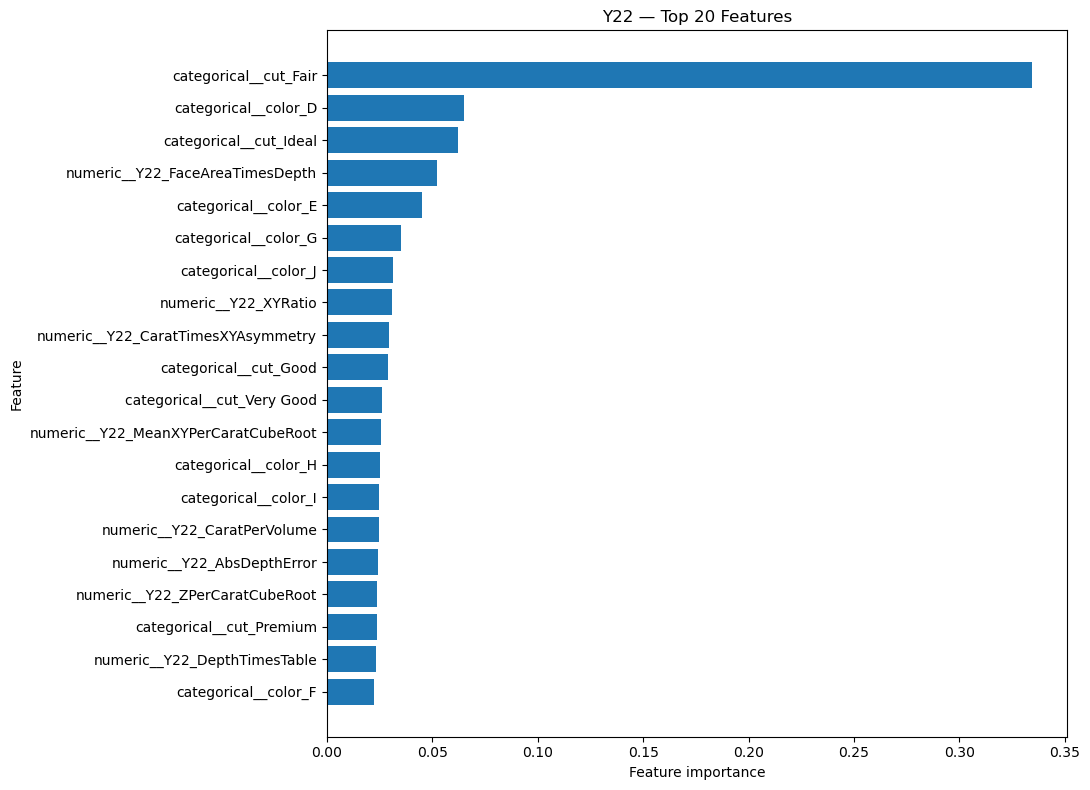

TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [1]:
# ==========================================================================================
# Y22 — MI-GUIDED CORRELATION PRUNING
#       PHYSICAL-ONLY DIAMOND CLARITY MODEL
# ==========================================================================================
#
# PURPOSE
# -------
#
# Improve Y21 feature selection.
#
# Y21 problem:
#
#     Correlation pruning moved through the feature list left -> right.
#
#     Therefore:
#
#         carat came first
#             ↓
#         carat survived
#             ↓
#         x / y / z / volume / etc. were removed
#
#     That means FEATURE ORDER partly decided what information survived.
#
#
# Y22 SOLUTION
# ------------
#
# 1. Generate all physical features.
#
# 2. Split data FIRST.
#
# 3. Using TRAINING DATA ONLY:
#
#       Calculate Mutual Information:
#
#           MI(feature, clarity)
#
# 4. Rank numerical features:
#
#       highest MI
#           ↓
#       lowest MI
#
# 5. Keep the most informative remaining feature.
#
# 6. Remove other features with:
#
#       |Pearson correlation| >= 0.75
#
#    relative to the selected feature.
#
# 7. Continue until every remaining selected pair has:
#
#       |r| < 0.75
#
#
# RESULT
# ------
#
# We keep DIFFERENT PHYSICAL PERSPECTIVES while removing redundancy.
#
#
# PRICE POLICY
# ------------
#
# Price is deleted immediately.
# Price is NEVER used.
#
#
# TARGET
# ------
#
#     I < SI < VS < VVS < IF
#
#
# SPLIT
# -----
#
#     70% train
#     15% validation
#     15% test
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer

from sklearn.feature_selection import (
    mutual_info_classif,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

from sklearn.model_selection import (
    train_test_split,
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.utils.class_weight import (
    compute_sample_weight,
)

from xgboost import (
    XGBClassifier,
)


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42


# Anything at +0.75 or -0.75 and beyond
# is treated as highly correlated.

CORRELATION_THRESHOLD = 0.75


DATA_PATH = Path(
    r"C:\Users\alihu\Projects\ML Course\Diamond\sideEDA\data\cleaned\diamonds_cleaned.csv"
)


OUTPUT_DIR = Path(
    "y22_outputs"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ==========================================================================================
# 3. CLARITY TARGET
# ==========================================================================================

CLARITY_CLASSES = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


CLARITY_TO_FAMILY = {

    "I1": 0,

    "SI2": 1,
    "SI1": 1,

    "VS2": 2,
    "VS1": 2,

    "VVS2": 3,
    "VVS1": 3,

    "IF": 4,
}


# ==========================================================================================
# 4. LOAD DATA
# ==========================================================================================

if not DATA_PATH.exists():

    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_PATH}"
    )


df = pd.read_csv(
    DATA_PATH
)


# Normalize column names.

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
)


# Remove accidental CSV index columns.

unnamed_columns = [
    column
    for column in df.columns
    if column.startswith(
        "unnamed:"
    )
]


if unnamed_columns:

    df = df.drop(
        columns=unnamed_columns
    )


print("=" * 140)
print("Y22 — MI-GUIDED PHYSICAL CLARITY MODEL")
print("=" * 140)


print(
    f"\nDataset:\n{DATA_PATH}"
)


print(
    f"\nRows loaded: {len(df):,}"
)


print(
    f"Columns loaded: {len(df.columns)}"
)


print(
    "\nColumns:"
)


print(
    df.columns.tolist()
)


# ==========================================================================================
# 5. REQUIRED COLUMNS
# ==========================================================================================

REQUIRED_COLUMNS = [

    "carat",

    "cut",
    "color",
    "clarity",

    "depth",
    "table",

    "x",
    "y",
    "z",
]


missing_columns = [

    column

    for column in REQUIRED_COLUMNS

    if column not in df.columns
]


if missing_columns:

    raise ValueError(
        f"Missing required columns: "
        f"{missing_columns}"
    )


# ==========================================================================================
# 6. DELETE PRICE
# ==========================================================================================

if "price" in df.columns:

    df = df.drop(
        columns=[
            "price"
        ]
    )


assert "price" not in df.columns


print(
    "\n✓ Price removed."
)


# ==========================================================================================
# 7. CLEAN DATA
# ==========================================================================================

y22_df = df.copy()


rows_before_cleaning = len(
    y22_df
)


# ------------------------------------------------------------------------------------------
# Clean categorical text
# ------------------------------------------------------------------------------------------

for column in [

    "cut",
    "color",
    "clarity",

]:

    y22_df[column] = (

        y22_df[column]

        .astype(str)

        .str.strip()
    )


# ------------------------------------------------------------------------------------------
# Numerical conversion
# ------------------------------------------------------------------------------------------

RAW_NUMERIC_COLUMNS = [

    "carat",

    "depth",
    "table",

    "x",
    "y",
    "z",
]


for column in RAW_NUMERIC_COLUMNS:

    y22_df[column] = pd.to_numeric(

        y22_df[column],

        errors="coerce",
    )


# ------------------------------------------------------------------------------------------
# Remove missing essential data
# ------------------------------------------------------------------------------------------

y22_df = y22_df.dropna(

    subset=REQUIRED_COLUMNS

).copy()


# ------------------------------------------------------------------------------------------
# Remove impossible physical measurements
# ------------------------------------------------------------------------------------------

for column in RAW_NUMERIC_COLUMNS:

    y22_df = y22_df[

        y22_df[column] > 0

    ].copy()


y22_df = y22_df.replace(

    [
        np.inf,
        -np.inf,
    ],

    np.nan,
)


y22_df = y22_df.reset_index(
    drop=True
)


print("\n")
print("=" * 140)
print("CLEANING")
print("=" * 140)


print(
    f"Rows before: {rows_before_cleaning:,}"
)


print(
    f"Rows after:  {len(y22_df):,}"
)


print(
    f"Removed:     "
    f"{rows_before_cleaning - len(y22_df):,}"
)


# ==========================================================================================
# 8. PHYSICAL SIZE FEATURES
# ==========================================================================================

y22_df["Y22_FaceArea"] = (

    y22_df["x"]
    *
    y22_df["y"]
)


y22_df["Y22_Volume"] = (

    y22_df["x"]
    *
    y22_df["y"]
    *
    y22_df["z"]
)


y22_df["Y22_FaceDiagonal"] = np.sqrt(

    y22_df["x"] ** 2
    +
    y22_df["y"] ** 2
)


# ==========================================================================================
# 9. SHAPE RATIOS
# ==========================================================================================

y22_df["Y22_XYRatio"] = (

    y22_df["x"]
    /
    y22_df["y"]
)


y22_df["Y22_XZRatio"] = (

    y22_df["x"]
    /
    y22_df["z"]
)


y22_df["Y22_YZRatio"] = (

    y22_df["y"]
    /
    y22_df["z"]
)


# ==========================================================================================
# 10. ABSOLUTE DIMENSION DIFFERENCES
# ==========================================================================================

y22_df["Y22_XYAbsDiff"] = np.abs(

    y22_df["x"]
    -
    y22_df["y"]
)


y22_df["Y22_XZAbsDiff"] = np.abs(

    y22_df["x"]
    -
    y22_df["z"]
)


y22_df["Y22_YZAbsDiff"] = np.abs(

    y22_df["y"]
    -
    y22_df["z"]
)


# ==========================================================================================
# 11. NORMALIZED DIFFERENCES
# ==========================================================================================

xy_mean = (

    y22_df["x"]
    +
    y22_df["y"]

) / 2.0


xz_mean = (

    y22_df["x"]
    +
    y22_df["z"]

) / 2.0


yz_mean = (

    y22_df["y"]
    +
    y22_df["z"]

) / 2.0


y22_df["Y22_XYNormalizedDiff"] = (

    y22_df["Y22_XYAbsDiff"]
    /
    xy_mean
)


y22_df["Y22_XZNormalizedDiff"] = (

    y22_df["Y22_XZAbsDiff"]
    /
    xz_mean
)


y22_df["Y22_YZNormalizedDiff"] = (

    y22_df["Y22_YZAbsDiff"]
    /
    yz_mean
)


# ==========================================================================================
# 12. SYMMETRY PROXY
# ==========================================================================================

y22_df["Y22_XYSymmetryProxy"] = (

    1.0
    -
    y22_df[
        "Y22_XYNormalizedDiff"
    ]
)


# ==========================================================================================
# 13. DIMENSION SUMMARY FEATURES
# ==========================================================================================

dimension_matrix = y22_df[
    [
        "x",
        "y",
        "z",
    ]
]


y22_df["Y22_MeanXY"] = (

    y22_df["x"]
    +
    y22_df["y"]

) / 2.0


y22_df["Y22_MeanXYZ"] = (

    dimension_matrix

    .mean(
        axis=1
    )
)


y22_df["Y22_MaxDimension"] = (

    dimension_matrix

    .max(
        axis=1
    )
)


y22_df["Y22_MinDimension"] = (

    dimension_matrix

    .min(
        axis=1
    )
)


y22_df["Y22_DimensionRange"] = (

    y22_df[
        "Y22_MaxDimension"
    ]

    -

    y22_df[
        "Y22_MinDimension"
    ]
)


y22_df["Y22_DimensionStd"] = (

    dimension_matrix

    .std(
        axis=1,
        ddof=0,
    )
)


y22_df["Y22_DimensionCV"] = (

    y22_df[
        "Y22_DimensionStd"
    ]

    /

    y22_df[
        "Y22_MeanXYZ"
    ]
)


# ==========================================================================================
# 14. CARAT-NORMALIZED DIMENSIONS
# ==========================================================================================

carat_cube_root = np.cbrt(

    y22_df["carat"]
)


y22_df["Y22_XPerCaratCubeRoot"] = (

    y22_df["x"]
    /
    carat_cube_root
)


y22_df["Y22_YPerCaratCubeRoot"] = (

    y22_df["y"]
    /
    carat_cube_root
)


y22_df["Y22_ZPerCaratCubeRoot"] = (

    y22_df["z"]
    /
    carat_cube_root
)


y22_df[
    "Y22_MeanXYPerCaratCubeRoot"
] = (

    y22_df[
        "Y22_MeanXY"
    ]

    /

    carat_cube_root
)


y22_df[
    "Y22_MeanXYZPerCaratCubeRoot"
] = (

    y22_df[
        "Y22_MeanXYZ"
    ]

    /

    carat_cube_root
)


# ==========================================================================================
# 15. WEIGHT / SIZE RELATIONSHIPS
# ==========================================================================================

y22_df["Y22_CaratPerVolume"] = (

    y22_df["carat"]

    /

    y22_df[
        "Y22_Volume"
    ]
)


y22_df["Y22_VolumePerCarat"] = (

    y22_df[
        "Y22_Volume"
    ]

    /

    y22_df["carat"]
)


y22_df[
    "Y22_CaratPerFaceArea"
] = (

    y22_df["carat"]

    /

    y22_df[
        "Y22_FaceArea"
    ]
)


y22_df[
    "Y22_FaceAreaPerCarat"
] = (

    y22_df[
        "Y22_FaceArea"
    ]

    /

    y22_df["carat"]
)


y22_df[
    "Y22_CaratPerMeanDimension"
] = (

    y22_df["carat"]

    /

    y22_df[
        "Y22_MeanXYZ"
    ]
)


# ==========================================================================================
# 16. DEPTH GEOMETRY
# ==========================================================================================

y22_df[
    "Y22_CalculatedDepthPct"
] = (

    2.0

    *

    y22_df["z"]

    /

    (
        y22_df["x"]
        +
        y22_df["y"]
    )

    *

    100.0
)


y22_df["Y22_DepthError"] = (

    y22_df["depth"]

    -

    y22_df[
        "Y22_CalculatedDepthPct"
    ]
)


y22_df[
    "Y22_AbsDepthError"
] = np.abs(

    y22_df[
        "Y22_DepthError"
    ]
)


y22_df[
    "Y22_DepthTableRatio"
] = (

    y22_df["depth"]

    /

    y22_df["table"]
)


y22_df[
    "Y22_TableDepthRatio"
] = (

    y22_df["table"]

    /

    y22_df["depth"]
)


y22_df[
    "Y22_DepthToFaceDiagonal"
] = (

    y22_df["z"]

    /

    y22_df[
        "Y22_FaceDiagonal"
    ]
)


y22_df[
    "Y22_DepthToFaceArea"
] = (

    y22_df["z"]

    /

    y22_df[
        "Y22_FaceArea"
    ]
)


# ==========================================================================================
# 17. COMPACTNESS
# ==========================================================================================

y22_df["Y22_Compactness"] = (

    y22_df["carat"]

    /

    (
        y22_df[
            "Y22_MeanXYZ"
        ]
        ** 3
    )
)


y22_df[
    "Y22_VolumeToMeanCube"
] = (

    y22_df[
        "Y22_Volume"
    ]

    /

    (
        y22_df[
            "Y22_MeanXYZ"
        ]
        ** 3
    )
)


# ==========================================================================================
# 18. INTERACTIONS
# ==========================================================================================

y22_df[
    "Y22_DepthTimesTable"
] = (

    y22_df["depth"]

    *

    y22_df["table"]
)


y22_df[
    "Y22_CaratTimesDepth"
] = (

    y22_df["carat"]

    *

    y22_df["depth"]
)


y22_df[
    "Y22_CaratTimesTable"
] = (

    y22_df["carat"]

    *

    y22_df["table"]
)


y22_df[
    "Y22_CaratTimesXYAsymmetry"
] = (

    y22_df["carat"]

    *

    y22_df[
        "Y22_XYNormalizedDiff"
    ]
)


y22_df[
    "Y22_VolumeTimesDepth"
] = (

    y22_df[
        "Y22_Volume"
    ]

    *

    y22_df["depth"]
)


y22_df[
    "Y22_FaceAreaTimesDepth"
] = (

    y22_df[
        "Y22_FaceArea"
    ]

    *

    y22_df["depth"]
)


# ==========================================================================================
# 19. CLEAN ENGINEERED VALUES
# ==========================================================================================

y22_df = y22_df.replace(

    [
        np.inf,
        -np.inf,
    ],

    np.nan,
)


# ==========================================================================================
# 20. TARGET
# ==========================================================================================

y22_df[
    "Clarity_Family_Target"
] = (

    y22_df["clarity"]

    .map(
        CLARITY_TO_FAMILY
    )
)


if y22_df[
    "Clarity_Family_Target"
].isna().any():

    bad_values = (

        y22_df.loc[
            y22_df[
                "Clarity_Family_Target"
            ].isna(),
            "clarity",
        ]

        .unique()

        .tolist()
    )


    raise ValueError(
        f"Unknown clarity values: "
        f"{bad_values}"
    )


y22_df[
    "Clarity_Family_Target"
] = (

    y22_df[
        "Clarity_Family_Target"
    ]

    .astype(int)
)


y = (

    y22_df[
        "Clarity_Family_Target"
    ]

    .to_numpy()
)


# ==========================================================================================
# 21. CLASS DISTRIBUTION
# ==========================================================================================

print("\n")
print("=" * 140)
print("CLARITY FAMILY DISTRIBUTION")
print("=" * 140)


for class_index, class_name in enumerate(
    CLARITY_CLASSES
):

    class_count = (
        y == class_index
    ).sum()


    class_percentage = (

        class_count

        /

        len(y)

        *

        100
    )


    print(

        f"{class_name:5s}: "

        f"{class_count:6,d} "

        f"({class_percentage:6.2f}%)"
    )


# ==========================================================================================
# 22. CANDIDATE NUMERICAL FEATURES
# ==========================================================================================

NUMERIC_FEATURES_ALL = [

    # Original measurements

    "carat",
    "depth",
    "table",

    "x",
    "y",
    "z",


    # Size

    "Y22_FaceArea",
    "Y22_Volume",
    "Y22_FaceDiagonal",


    # Shape ratios

    "Y22_XYRatio",
    "Y22_XZRatio",
    "Y22_YZRatio",


    # Absolute differences

    "Y22_XYAbsDiff",
    "Y22_XZAbsDiff",
    "Y22_YZAbsDiff",


    # Normalized differences

    "Y22_XYNormalizedDiff",
    "Y22_XZNormalizedDiff",
    "Y22_YZNormalizedDiff",


    # Symmetry

    "Y22_XYSymmetryProxy",


    # Dimension summaries

    "Y22_MeanXY",
    "Y22_MeanXYZ",

    "Y22_MaxDimension",
    "Y22_MinDimension",

    "Y22_DimensionRange",
    "Y22_DimensionStd",
    "Y22_DimensionCV",


    # Weight-normalized dimensions

    "Y22_XPerCaratCubeRoot",
    "Y22_YPerCaratCubeRoot",
    "Y22_ZPerCaratCubeRoot",

    "Y22_MeanXYPerCaratCubeRoot",
    "Y22_MeanXYZPerCaratCubeRoot",


    # Weight / geometry

    "Y22_CaratPerVolume",
    "Y22_VolumePerCarat",

    "Y22_CaratPerFaceArea",
    "Y22_FaceAreaPerCarat",

    "Y22_CaratPerMeanDimension",


    # Depth relationships

    "Y22_CalculatedDepthPct",

    "Y22_DepthError",
    "Y22_AbsDepthError",

    "Y22_DepthTableRatio",
    "Y22_TableDepthRatio",

    "Y22_DepthToFaceDiagonal",
    "Y22_DepthToFaceArea",


    # Compactness

    "Y22_Compactness",
    "Y22_VolumeToMeanCube",


    # Interactions

    "Y22_DepthTimesTable",

    "Y22_CaratTimesDepth",
    "Y22_CaratTimesTable",

    "Y22_CaratTimesXYAsymmetry",

    "Y22_VolumeTimesDepth",
    "Y22_FaceAreaTimesDepth",
]


CATEGORICAL_FEATURES = [

    "cut",
    "color",
]


# ==========================================================================================
# 23. PRICE LEAKAGE CHECK
# ==========================================================================================

for feature in (

    NUMERIC_FEATURES_ALL

    +

    CATEGORICAL_FEATURES

):

    if "price" in feature.lower():

        raise RuntimeError(

            f"PRICE LEAKAGE: "
            f"{feature}"
        )


print(
    f"\nCandidate numeric features: "
    f"{len(NUMERIC_FEATURES_ALL)}"
)


# ==========================================================================================
# 24. CREATE X
# ==========================================================================================

ALL_FEATURES = (

    NUMERIC_FEATURES_ALL

    +

    CATEGORICAL_FEATURES
)


X = (

    y22_df[
        ALL_FEATURES
    ]

    .copy()
)


# ==========================================================================================
# 25. 70 / 15 / 15 SPLIT
# ==========================================================================================

indices = np.arange(
    len(
        y22_df
    )
)


train_idx, temp_idx = train_test_split(

    indices,

    test_size=0.30,

    random_state=RANDOM_STATE,

    stratify=y,
)


valid_idx, test_idx = train_test_split(

    temp_idx,

    test_size=0.50,

    random_state=RANDOM_STATE,

    stratify=y[
        temp_idx
    ],
)


y_train = y[
    train_idx
]


y_valid = y[
    valid_idx
]


y_test = y[
    test_idx
]


print("\n")
print("=" * 140)
print("DATA SPLIT")
print("=" * 140)


print(
    f"Training:   "
    f"{len(train_idx):,}"
)


print(
    f"Validation: "
    f"{len(valid_idx):,}"
)


print(
    f"Testing:    "
    f"{len(test_idx):,}"
)


# ==========================================================================================
# 26. TRAINING-ONLY MEDIAN IMPUTATION
# ==========================================================================================

training_medians = (

    X.iloc[
        train_idx
    ][
        NUMERIC_FEATURES_ALL
    ]

    .median()
)


X.loc[
    :,
    NUMERIC_FEATURES_ALL
] = (

    X[
        NUMERIC_FEATURES_ALL
    ]

    .fillna(
        training_medians
    )
)


# ==========================================================================================
# 27. TRAINING NUMERICAL DATA
# ==========================================================================================

training_numeric = (

    X.iloc[
        train_idx
    ][
        NUMERIC_FEATURES_ALL
    ]

    .copy()
)


# ==========================================================================================
# 28. CORRELATION MATRIX
# ==========================================================================================

correlation_matrix = (

    training_numeric

    .corr(
        method="pearson"
    )
)


correlation_matrix.to_csv(

    OUTPUT_DIR
    /
    "y22_full_correlation_matrix.csv"
)


# ==========================================================================================
# 29. MUTUAL INFORMATION
# ==========================================================================================
#
# This is the major Y22 difference.
#
# MI measures how informative each numerical feature is about the
# clarity-family target.
#
# It can detect nonlinear relationships too.
#
# IMPORTANT:
#
# TRAINING DATA ONLY.
# ==========================================================================================

mi_scores = mutual_info_classif(

    training_numeric,

    y_train,

    random_state=RANDOM_STATE,
)


mi_df = pd.DataFrame(
    {

        "Feature":
            NUMERIC_FEATURES_ALL,

        "Mutual_Information":
            mi_scores,
    }
)


mi_df = (

    mi_df

    .sort_values(
        "Mutual_Information",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


mi_df[
    "MI_Rank"
] = (

    np.arange(
        1,
        len(mi_df) + 1,
    )
)


print("\n")
print("=" * 140)
print("MUTUAL INFORMATION RANKING")
print("=" * 140)


print(

    mi_df[
        [
            "MI_Rank",
            "Feature",
            "Mutual_Information",
        ]
    ]

    .round(
        6
    )

    .to_string(
        index=False
    )
)


mi_df.to_csv(

    OUTPUT_DIR
    /
    "y22_mutual_information.csv",

    index=False,
)


# ==========================================================================================
# 30. MI-GUIDED CORRELATION PRUNING
# ==========================================================================================
#
# ALGORITHM
# ---------
#
# Sort:
#
#     highest MI
#          ↓
#     lowest MI
#
#
# For each candidate:
#
#     Is it >= 0.75 correlated with ANY already-selected feature?
#
#         NO
#             ↓
#           KEEP
#
#         YES
#             ↓
#           DROP
#
#
# Therefore:
#
# the highest-MI feature in a redundant perspective tends to survive.
# ==========================================================================================

ranked_features = (

    mi_df[
        "Feature"
    ]

    .tolist()
)


selected_numeric_features = []


dropped_numeric_features = []


for candidate_feature in ranked_features:

    conflicting_features = []


    # ------------------------------------------------------------------
    # Compare candidate against features already retained.
    # ------------------------------------------------------------------

    for selected_feature in selected_numeric_features:

        correlation = (

            correlation_matrix.loc[
                candidate_feature,
                selected_feature,
            ]
        )


        if pd.isna(
            correlation
        ):

            continue


        if (
            abs(
                correlation
            )
            >=
            CORRELATION_THRESHOLD
        ):

            conflicting_features.append(
                (
                    selected_feature,
                    correlation,
                )
            )


    # ------------------------------------------------------------------
    # No conflict -> retain.
    # ------------------------------------------------------------------

    if not conflicting_features:

        selected_numeric_features.append(
            candidate_feature
        )

        continue


    # ------------------------------------------------------------------
    # Conflict -> drop candidate.
    #
    # Store its strongest correlation with a selected representative.
    # ------------------------------------------------------------------

    representative_feature, strongest_corr = max(

        conflicting_features,

        key=lambda pair: abs(
            pair[1]
        ),
    )


    candidate_mi = (

        mi_df.loc[
            mi_df["Feature"]
            ==
            candidate_feature,
            "Mutual_Information",
        ]

        .iloc[0]
    )


    representative_mi = (

        mi_df.loc[
            mi_df["Feature"]
            ==
            representative_feature,
            "Mutual_Information",
        ]

        .iloc[0]
    )


    dropped_numeric_features.append(
        {

            "Dropped_Feature":
                candidate_feature,

            "Selected_Representative":
                representative_feature,

            "Correlation":
                strongest_corr,

            "Absolute_Correlation":
                abs(
                    strongest_corr
                ),

            "Dropped_MI":
                candidate_mi,

            "Representative_MI":
                representative_mi,
        }
    )


# ==========================================================================================
# 31. PRUNING RESULTS
# ==========================================================================================

selected_mi_df = (

    mi_df[
        mi_df[
            "Feature"
        ].isin(
            selected_numeric_features
        )
    ]

    .copy()

    .sort_values(
        "Mutual_Information",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


dropped_features_df = pd.DataFrame(
    dropped_numeric_features
)


print("\n")
print("=" * 140)
print("Y22 — MI-GUIDED CORRELATION PRUNING")
print("=" * 140)


print(
    f"Before pruning: "
    f"{len(NUMERIC_FEATURES_ALL)}"
)


print(
    f"After pruning:  "
    f"{len(selected_numeric_features)}"
)


print(
    f"Removed:        "
    f"{len(dropped_numeric_features)}"
)


print("\n")
print("SELECTED REPRESENTATIVES")
print("-" * 100)


print(

    selected_mi_df[
        [
            "Feature",
            "Mutual_Information",
        ]
    ]

    .round(
        6
    )

    .to_string(
        index=False
    )
)


print("\n")
print("DROPPED REDUNDANT FEATURES")
print("-" * 100)


if dropped_features_df.empty:

    print(
        "None"
    )


else:

    print(

        dropped_features_df

        .sort_values(
            "Absolute_Correlation",
            ascending=False,
        )

        .round(
            5
        )

        .to_string(
            index=False
        )
    )


# ==========================================================================================
# 32. SAVE FEATURE SELECTION
# ==========================================================================================

selected_mi_df.to_csv(

    OUTPUT_DIR
    /
    "y22_selected_numeric_features.csv",

    index=False,
)


dropped_features_df.to_csv(

    OUTPUT_DIR
    /
    "y22_dropped_correlated_features.csv",

    index=False,
)


# ==========================================================================================
# 33. VERIFY MAXIMUM CORRELATION AFTER PRUNING
# ==========================================================================================

selected_correlation_matrix = (

    training_numeric[
        selected_numeric_features
    ]

    .corr(
        method="pearson"
    )
)


selected_correlation_matrix.to_csv(

    OUTPUT_DIR
    /
    "y22_selected_feature_correlation_matrix.csv"
)


upper_triangle_mask = np.triu(

    np.ones(
        selected_correlation_matrix.shape
    ),

    k=1,

).astype(bool)


upper_triangle = (

    selected_correlation_matrix

    .where(
        upper_triangle_mask
    )
)


max_remaining_correlation = (

    upper_triangle

    .abs()

    .max()

    .max()
)


print(
    f"\nMaximum remaining |r|: "
    f"{max_remaining_correlation:.4f}"
)


if (
    max_remaining_correlation
    >=
    CORRELATION_THRESHOLD
):

    raise RuntimeError(

        "Correlation pruning failed: "
        "selected features still contain "
        "a pair above the threshold."
    )


print(
    "✓ Every retained numeric pair is below "
    "the correlation threshold."
)


# ==========================================================================================
# 34. CORRELATION MATRIX PLOT
# ==========================================================================================

matrix_size = max(

    10,

    len(
        selected_numeric_features
    )
    *
    0.65,
)


fig, ax = plt.subplots(

    figsize=(
        matrix_size,
        matrix_size,
    )
)


image = ax.imshow(

    selected_correlation_matrix.values,

    vmin=-1,

    vmax=1,

    aspect="auto",
)


ax.set_xticks(

    np.arange(
        len(
            selected_numeric_features
        )
    )
)


ax.set_yticks(

    np.arange(
        len(
            selected_numeric_features
        )
    )
)


ax.set_xticklabels(

    selected_numeric_features,

    rotation=90,

    fontsize=8,
)


ax.set_yticklabels(

    selected_numeric_features,

    fontsize=8,
)


ax.set_title(

    "Y22 — MI-Guided Selected Feature Correlations"
)


fig.colorbar(

    image,

    ax=ax,

    label="Pearson correlation",
)


fig.tight_layout()


fig.savefig(

    OUTPUT_DIR
    /
    "y22_selected_feature_correlation_matrix.png",

    dpi=200,

    bbox_inches="tight",
)


plt.show()


# ==========================================================================================
# 35. MUTUAL INFORMATION PLOT
# ==========================================================================================

plot_mi_df = (

    mi_df

    .head(
        25
    )

    .sort_values(
        "Mutual_Information",
        ascending=True,
    )
)


fig, ax = plt.subplots(

    figsize=(
        11,
        9,
    )
)


ax.barh(

    plot_mi_df[
        "Feature"
    ],

    plot_mi_df[
        "Mutual_Information"
    ],
)


ax.set_xlabel(
    "Mutual information with clarity"
)


ax.set_ylabel(
    "Feature"
)


ax.set_title(

    "Y22 — Top 25 Numerical Features by Mutual Information"
)


fig.tight_layout()


fig.savefig(

    OUTPUT_DIR
    /
    "y22_mutual_information_top25.png",

    dpi=200,

    bbox_inches="tight",
)


plt.show()


# ==========================================================================================
# 36. ONE-HOT ENCODER
# ==========================================================================================

try:

    categorical_encoder = OneHotEncoder(

        handle_unknown="ignore",

        sparse_output=False,
    )


except TypeError:

    categorical_encoder = OneHotEncoder(

        handle_unknown="ignore",

        sparse=False,
    )


# ==========================================================================================
# 37. PREPROCESSOR
# ==========================================================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",

            StandardScaler(),

            selected_numeric_features,
        ),


        (
            "categorical",

            categorical_encoder,

            CATEGORICAL_FEATURES,
        ),
    ],

    remainder="drop",
)


# ==========================================================================================
# 38. FIT ON TRAIN
# ==========================================================================================

X_train = (

    preprocessor

    .fit_transform(

        X.iloc[
            train_idx
        ]
    )

    .astype(
        np.float32
    )
)


X_valid = (

    preprocessor

    .transform(

        X.iloc[
            valid_idx
        ]
    )

    .astype(
        np.float32
    )
)


X_test = (

    preprocessor

    .transform(

        X.iloc[
            test_idx
        ]
    )

    .astype(
        np.float32
    )
)


feature_names = (

    preprocessor

    .get_feature_names_out()
)


print("\n")
print("=" * 140)
print("FINAL MODEL INPUT")
print("=" * 140)


print(
    f"Selected numerical perspectives: "
    f"{len(selected_numeric_features)}"
)


print(
    f"Encoded model inputs: "
    f"{X_train.shape[1]}"
)


print(
    f"X_train: {X_train.shape}"
)


print(
    f"X_valid: {X_valid.shape}"
)


print(
    f"X_test:  {X_test.shape}"
)


# ==========================================================================================
# 39. PRICE LEAKAGE CHECK
# ==========================================================================================

price_features = [

    feature

    for feature in feature_names

    if "price" in str(
        feature
    ).lower()
]


if price_features:

    raise RuntimeError(

        f"PRICE LEAKAGE FOUND: "
        f"{price_features}"
    )


print(
    "\n✓ Price leakage check passed."
)


# ==========================================================================================
# 40. CLASS BALANCING
# ==========================================================================================

sample_weights = compute_sample_weight(

    class_weight="balanced",

    y=y_train,
)


# ==========================================================================================
# 41. XGBOOST
# ==========================================================================================
#
# Y21 reached its maximum 1499/1500 trees.
#
# Therefore Y22 allows more trees so early stopping can actually
# determine where improvement stops.
# ==========================================================================================

model = XGBClassifier(

    objective="multi:softprob",

    num_class=len(
        CLARITY_CLASSES
    ),

    eval_metric="mlogloss",

    n_estimators=3000,

    learning_rate=0.03,

    max_depth=6,

    min_child_weight=2,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_alpha=0.10,

    reg_lambda=1.0,

    tree_method="hist",

    random_state=RANDOM_STATE,

    n_jobs=-1,

    early_stopping_rounds=100,
)


print("\n")
print("=" * 140)
print("TRAINING Y22")
print("=" * 140)


model.fit(

    X_train,

    y_train,

    sample_weight=sample_weights,

    eval_set=[
        (
            X_valid,
            y_valid,
        )
    ],

    verbose=False,
)


print(
    f"Best iteration: "
    f"{model.best_iteration}"
)


# ==========================================================================================
# 42. METRICS
# ==========================================================================================

def calculate_metrics(
    y_true,
    y_pred,
    dataset_name,
):

    family_distance = np.abs(

        y_true
        -
        y_pred
    )


    return {

        "Dataset":
            dataset_name,


        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,


        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,


        "Macro_Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,


        "Macro_Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,


        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,


        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,


        "Mean_Family_Error":
            family_distance.mean(),


        "Within_1_Family":
            (
                family_distance <= 1
            ).mean()
            *
            100,


        "Severe_Error":
            (
                family_distance > 1
            ).mean()
            *
            100,
    }


# ==========================================================================================
# 43. VALIDATION
# ==========================================================================================

validation_predictions = model.predict(
    X_valid
)


validation_metrics = calculate_metrics(

    y_valid,

    validation_predictions,

    "Validation",
)


# ==========================================================================================
# 44. TEST
# ==========================================================================================

test_predictions = model.predict(
    X_test
)


test_metrics = calculate_metrics(

    y_test,

    test_predictions,

    "Test",
)


# ==========================================================================================
# 45. RESULTS
# ==========================================================================================

results_df = pd.DataFrame(
    [
        validation_metrics,
        test_metrics,
    ]
)


print("\n")
print("=" * 150)
print("Y22 — FINAL RESULTS")
print("=" * 150)


print(

    results_df

    .round(
        3
    )

    .to_string(
        index=False
    )
)


results_df.to_csv(

    OUTPUT_DIR
    /
    "y22_metrics.csv",

    index=False,
)


# ==========================================================================================
# 46. CLASSIFICATION REPORT
# ==========================================================================================

print("\n")
print("=" * 140)
print("TEST CLASSIFICATION REPORT")
print("=" * 140)


print(

    classification_report(

        y_test,

        test_predictions,

        labels=np.arange(
            len(
                CLARITY_CLASSES
            )
        ),

        target_names=CLARITY_CLASSES,

        digits=4,

        zero_division=0,
    )
)


# ==========================================================================================
# 47. CONFUSION MATRIX
# ==========================================================================================

confusion = confusion_matrix(

    y_test,

    test_predictions,

    labels=np.arange(
        len(
            CLARITY_CLASSES
        )
    ),
)


confusion_percent = (

    confusion

    /

    np.maximum(

        confusion.sum(
            axis=1,
            keepdims=True,
        ),

        1,
    )

    *

    100
)


confusion_percent_df = pd.DataFrame(

    confusion_percent,

    index=[
        f"Actual_{name}"
        for name in CLARITY_CLASSES
    ],

    columns=[
        f"Pred_{name}"
        for name in CLARITY_CLASSES
    ],
)


print("\n")
print("=" * 140)
print("CONFUSION MATRIX (%)")
print("=" * 140)


print(

    confusion_percent_df

    .round(
        2
    )

    .to_string()
)


confusion_percent_df.to_csv(

    OUTPUT_DIR
    /
    "y22_confusion_matrix_percent.csv"
)


# ==========================================================================================
# 48. CONFUSION MATRIX PLOT
# ==========================================================================================

fig, ax = plt.subplots(

    figsize=(
        8,
        7,
    )
)


display = ConfusionMatrixDisplay(

    confusion_matrix=confusion,

    display_labels=CLARITY_CLASSES,
)


display.plot(

    ax=ax,

    values_format="d",
)


ax.set_title(

    "Y22 — MI-Guided Physical Clarity Model"
)


fig.tight_layout()


fig.savefig(

    OUTPUT_DIR
    /
    "y22_confusion_matrix.png",

    dpi=200,

    bbox_inches="tight",
)


plt.show()


# ==========================================================================================
# 49. FEATURE IMPORTANCE
# ==========================================================================================

importance_df = pd.DataFrame(
    {

        "Feature":
            feature_names,

        "Importance":
            model.feature_importances_,
    }
)


importance_df = (

    importance_df

    .sort_values(
        "Importance",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 140)
print("Y22 — TOP 30 MODEL FEATURES")
print("=" * 140)


print(

    importance_df

    .head(
        30
    )

    .round(
        6
    )

    .to_string(
        index=False
    )
)


importance_df.to_csv(

    OUTPUT_DIR
    /
    "y22_feature_importance.csv",

    index=False,
)


# ==========================================================================================
# 50. FEATURE IMPORTANCE PLOT
# ==========================================================================================

top_features = (

    importance_df

    .head(
        20
    )

    .sort_values(
        "Importance",
        ascending=True,
    )
)


fig, ax = plt.subplots(

    figsize=(
        11,
        8,
    )
)


ax.barh(

    top_features[
        "Feature"
    ],

    top_features[
        "Importance"
    ],
)


ax.set_xlabel(
    "Feature importance"
)


ax.set_ylabel(
    "Feature"
)


ax.set_title(
    "Y22 — Top 20 Features"
)


fig.tight_layout()


fig.savefig(

    OUTPUT_DIR
    /
    "y22_top20_feature_importance.png",

    dpi=200,

    bbox_inches="tight",
)


plt.show()


# ==========================================================================================
# 51. SAVE PREDICTIONS
# ==========================================================================================

prediction_df = pd.DataFrame(
    {

        "Actual_Class": [

            CLARITY_CLASSES[
                value
            ]

            for value in y_test
        ],


        "Predicted_Class": [

            CLARITY_CLASSES[
                value
            ]

            for value in test_predictions
        ],


        "Actual_Code":
            y_test,


        "Predicted_Code":
            test_predictions,


        "Family_Error":
            np.abs(
                y_test
                -
                test_predictions
            ),
    }
)


prediction_df.to_csv(

    OUTPUT_DIR
    /
    "y22_test_predictions.csv",

    index=False,
)


# ==========================================================================================
# 52. OPTIONAL AUTOMATIC Y21 COMPARISON
# ==========================================================================================
#
# If y21_outputs/y21_metrics.csv exists,
# compare Y22 against it automatically.
# ==========================================================================================

Y21_METRICS_PATH = Path(

    "y21_outputs"
    /
    "y21_metrics.csv"
)


if Y21_METRICS_PATH.exists():

    y21_results = pd.read_csv(
        Y21_METRICS_PATH
    )


    y21_test_row = (

        y21_results[
            y21_results[
                "Dataset"
            ]
            ==
            "Test"
        ]

        .iloc[0]
    )


    print("\n")
    print("=" * 150)
    print("Y21 VS Y22")
    print("=" * 150)


    comparison_rows = []


    for metric in [

        "Accuracy",

        "Balanced_Accuracy",

        "Macro_F1",

        "Weighted_F1",

        "Within_1_Family",

        "Severe_Error",

    ]:

        y21_value = (
            y21_test_row[
                metric
            ]
        )


        y22_value = (
            test_metrics[
                metric
            ]
        )


        change = (
            y22_value
            -
            y21_value
        )


        comparison_rows.append(
            {

                "Metric":
                    metric,

                "Y21":
                    y21_value,

                "Y22":
                    y22_value,

                "Change":
                    change,
            }
        )


    comparison_df = pd.DataFrame(
        comparison_rows
    )


    print(

        comparison_df

        .round(
            3
        )

        .to_string(
            index=False
        )
    )


    comparison_df.to_csv(

        OUTPUT_DIR
        /
        "y22_vs_y21.csv",

        index=False,
    )


# ==========================================================================================
# 53. FINAL SUMMARY
# ==========================================================================================

print("\n")
print("=" * 150)
print("Y22 COMPLETE")
print("=" * 150)


print(
    f"""
PRICE
-----

Price used:
    NO


FEATURE SELECTION
-----------------

Candidate numerical features:
    {len(NUMERIC_FEATURES_ALL)}

Selection method:
    Mutual Information ranked correlation pruning

Correlation threshold:
    |r| >= {CORRELATION_THRESHOLD:.2f}

Selected numerical perspectives:
    {len(selected_numeric_features)}

Removed redundant features:
    {len(dropped_numeric_features)}

Maximum remaining |r|:
    {max_remaining_correlation:.4f}

Final encoded model inputs:
    {X_train.shape[1]}


MODEL
-----

Best XGBoost iteration:
    {model.best_iteration}


TEST PERFORMANCE
----------------

Accuracy:
    {test_metrics['Accuracy']:.2f}%

Balanced Accuracy:
    {test_metrics['Balanced_Accuracy']:.2f}%

Macro Precision:
    {test_metrics['Macro_Precision']:.2f}%

Macro Recall:
    {test_metrics['Macro_Recall']:.2f}%

Macro F1:
    {test_metrics['Macro_F1']:.2f}%

Weighted F1:
    {test_metrics['Weighted_F1']:.2f}%

Mean Family Error:
    {test_metrics['Mean_Family_Error']:.4f}

Within ±1 Family:
    {test_metrics['Within_1_Family']:.2f}%

Severe Error:
    {test_metrics['Severe_Error']:.2f}%


OUTPUT DIRECTORY
----------------

{OUTPUT_DIR.resolve()}
"""
)

In [ ]:
# ==========================================================================================
# Y23 — OPTUNA-TUNED ORDINAL MODEL TOURNAMENT
# ==========================================================================================
#
# MODELS
# ------
# 1. Ordinal Random Forest
# 2. Ordinal XGBoost
# 3. Ordinal Neural Network
#
# TARGET ORDER
# ------------
#
#       I < SI < VS < VVS < IF
#
# Every model learns four cumulative questions:
#
#       P(Y > I)
#       P(Y > SI)
#       P(Y > VS)
#       P(Y > VVS)
#
# So these are genuinely ORDINAL models.
#
#
# FEATURE PIPELINE
# ----------------
#
# cleaned diamonds CSV
#       ↓
# DELETE price
#       ↓
# physical feature engineering
#       ↓
# 70 / 15 / 15 split
#       ↓
# TRAIN ONLY:
#       Mutual Information
#       Pearson correlation
#       keep strongest MI representative
#       remove |r| >= 0.75 redundancy
#       ↓
# scaling + one-hot encoding
#       ↓
# Optuna tuning
#       ↓
# final train + validation model
#       ↓
# test once
#
#
# OPTUNA PRIMARY OBJECTIVE
# ------------------------
#
#       Validation Macro F1
#
#
# FULL METRICS
# ------------
#
# Classification:
#   Accuracy
#   Balanced Accuracy
#   Micro/Macro/Weighted Precision
#   Micro/Macro/Weighted Recall
#   Micro/Macro/Weighted F1
#   Macro Jaccard
#   MCC
#   Geometric Mean Recall
#
# Ordinal:
#   Cohen Kappa
#   Linear Weighted Kappa
#   Quadratic Weighted Kappa
#   Ordinal MAE
#   Ordinal MSE
#   Ordinal RMSE
#   Median Absolute Error
#   Mean Signed Error
#   Exact accuracy
#   Within ±1
#   Within ±2
#   Exactly 1 off
#   Exactly 2 off
#   Severe Error (>1)
#   Very Severe Error (>2)
#   Too-high predictions
#   Too-low predictions
#
# Probability:
#   Log Loss
#   Multiclass Brier Score
#   Ranked Probability Score
#   Top-2 Accuracy
#   Macro ROC-AUC
#   Weighted ROC-AUC
#   Macro PR-AUC
#   Weighted PR-AUC
#
# Calibration:
#   ECE
#   Mean Confidence
#   Confidence when correct
#   Confidence when wrong
#   Prediction Entropy
#
# Per class:
#   Precision
#   Recall/Sensitivity
#   Specificity
#   F1
#   NPV
#   FPR
#   FNR
#   ROC-AUC
#   PR-AUC
#
# Ordinal boundaries:
#   > I
#   > SI
#   > VS
#   > VVS
#
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

from pathlib import Path
import gc
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    hamming_loss,
    jaccard_score,
    log_loss,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    top_k_accuracy_score,
)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. EXTERNAL PACKAGES
# ==========================================================================================

try:
    import optuna

except ImportError as exc:

    raise ImportError(
        "\nOptuna is missing.\n"
        "Install with:\n\n"
        "pip install optuna\n"
    ) from exc


try:
    import tensorflow as tf
    from tensorflow import keras

except ImportError as exc:

    raise ImportError(
        "\nTensorFlow is missing.\n"
        "Install with:\n\n"
        "pip install tensorflow\n"
    ) from exc


warnings.filterwarnings(
    "ignore"
)


# Reduce Optuna console spam.
optuna.logging.set_verbosity(
    optuna.logging.WARNING
)


# ==========================================================================================
# 3. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42

CORRELATION_THRESHOLD = 0.75


DATA_PATH = Path(
    r"C:\Users\alihu\Projects\ML Course\Diamond\sideEDA\data\cleaned\diamonds_cleaned.csv"
)


OUTPUT_DIR = Path(
    "y23_optuna_ordinal"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------------------------------------
# OPTUNA TRIAL COUNTS
#
# First run:
#
# RF  = 20
# XGB = 25
# ANN = 20
#
# Later, if everything works:
#
# RF  = 40+
# XGB = 50+
# ANN = 40+
# ------------------------------------------------------------------------------------------

RF_TRIALS = 20

XGB_TRIALS = 25

ANN_TRIALS = 20


# ==========================================================================================
# 4. CLARITY ORDER
# ==========================================================================================

CLARITY_CLASSES = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


CLARITY_TO_FAMILY = {

    "I1": 0,

    "SI2": 1,
    "SI1": 1,

    "VS2": 2,
    "VS1": 2,

    "VVS2": 3,
    "VVS1": 3,

    "IF": 4,
}


N_CLASSES = len(
    CLARITY_CLASSES
)


N_THRESHOLDS = (
    N_CLASSES - 1
)


# ==========================================================================================
# 5. REPRODUCIBILITY
# ==========================================================================================

np.random.seed(
    RANDOM_STATE
)


tf.keras.utils.set_random_seed(
    RANDOM_STATE
)


# ==========================================================================================
# 6. LOAD DATA
# ==========================================================================================

if not DATA_PATH.exists():

    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_PATH}"
    )


df = pd.read_csv(
    DATA_PATH
)


df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
)


unnamed_columns = [
    column
    for column in df.columns
    if column.startswith("unnamed:")
]


if unnamed_columns:

    df = df.drop(
        columns=unnamed_columns
    )


print("=" * 160)
print("Y23 — OPTUNA ORDINAL MODEL TOURNAMENT")
print("=" * 160)


print(
    f"\nDataset:\n{DATA_PATH}"
)


print(
    f"\nRows loaded: {len(df):,}"
)


print(
    f"Columns: {df.columns.tolist()}"
)


# ==========================================================================================
# 7. DELETE PRICE
# ==========================================================================================

if "price" in df.columns:

    df = df.drop(
        columns=["price"]
    )


assert "price" not in df.columns


print(
    "\n✓ PRICE REMOVED"
)


# ==========================================================================================
# 8. CLEAN DATA
# ==========================================================================================

REQUIRED_COLUMNS = [

    "carat",

    "cut",
    "color",
    "clarity",

    "depth",
    "table",

    "x",
    "y",
    "z",
]


missing_columns = [

    column

    for column in REQUIRED_COLUMNS

    if column not in df.columns
]


if missing_columns:

    raise ValueError(
        f"Missing columns: "
        f"{missing_columns}"
    )


work_df = df.copy()


for column in [
    "cut",
    "color",
    "clarity",
]:

    work_df[column] = (

        work_df[column]

        .astype(str)

        .str.strip()
    )


RAW_NUMERIC_COLUMNS = [

    "carat",

    "depth",
    "table",

    "x",
    "y",
    "z",
]


for column in RAW_NUMERIC_COLUMNS:

    work_df[column] = pd.to_numeric(

        work_df[column],

        errors="coerce",
    )


work_df = work_df.dropna(
    subset=REQUIRED_COLUMNS
).copy()


for column in RAW_NUMERIC_COLUMNS:

    work_df = work_df[

        work_df[column] > 0

    ].copy()


work_df = work_df.reset_index(
    drop=True
)


print(
    f"\nRows after cleaning: "
    f"{len(work_df):,}"
)


# ==========================================================================================
# 9. FEATURE ENGINEERING
# ==========================================================================================

def engineer_features(
    data: pd.DataFrame,
) -> pd.DataFrame:

    data = data.copy()


    # --------------------------------------------------------------------------------------
    # SIZE
    # --------------------------------------------------------------------------------------

    data["Y23_FaceArea"] = (

        data["x"]
        *
        data["y"]
    )


    data["Y23_Volume"] = (

        data["x"]
        *
        data["y"]
        *
        data["z"]
    )


    data["Y23_FaceDiagonal"] = np.sqrt(

        data["x"] ** 2

        +

        data["y"] ** 2
    )


    # --------------------------------------------------------------------------------------
    # RATIOS
    # --------------------------------------------------------------------------------------

    data["Y23_XYRatio"] = (

        data["x"]

        /

        data["y"]
    )


    data["Y23_XZRatio"] = (

        data["x"]

        /

        data["z"]
    )


    data["Y23_YZRatio"] = (

        data["y"]

        /

        data["z"]
    )


    # --------------------------------------------------------------------------------------
    # ABSOLUTE DIFFERENCES
    # --------------------------------------------------------------------------------------

    data["Y23_XYAbsDiff"] = np.abs(

        data["x"]

        -

        data["y"]
    )


    data["Y23_XZAbsDiff"] = np.abs(

        data["x"]

        -

        data["z"]
    )


    data["Y23_YZAbsDiff"] = np.abs(

        data["y"]

        -

        data["z"]
    )


    # --------------------------------------------------------------------------------------
    # NORMALIZED DIFFERENCES
    # --------------------------------------------------------------------------------------

    xy_mean = (

        data["x"]

        +

        data["y"]

    ) / 2.0


    xz_mean = (

        data["x"]

        +

        data["z"]

    ) / 2.0


    yz_mean = (

        data["y"]

        +

        data["z"]

    ) / 2.0


    data["Y23_XYNormalizedDiff"] = (

        data["Y23_XYAbsDiff"]

        /

        xy_mean
    )


    data["Y23_XZNormalizedDiff"] = (

        data["Y23_XZAbsDiff"]

        /

        xz_mean
    )


    data["Y23_YZNormalizedDiff"] = (

        data["Y23_YZAbsDiff"]

        /

        yz_mean
    )


    # --------------------------------------------------------------------------------------
    # SYMMETRY PROXY
    # --------------------------------------------------------------------------------------

    data["Y23_XYSymmetryProxy"] = (

        1.0

        -

        data[
            "Y23_XYNormalizedDiff"
        ]
    )


    # --------------------------------------------------------------------------------------
    # DIMENSIONS
    # --------------------------------------------------------------------------------------

    dimensions = data[
        [
            "x",
            "y",
            "z",
        ]
    ]


    data["Y23_MeanXY"] = (

        data["x"]

        +

        data["y"]

    ) / 2.0


    data["Y23_MeanXYZ"] = (

        dimensions.mean(
            axis=1
        )
    )


    data["Y23_MaxDimension"] = (

        dimensions.max(
            axis=1
        )
    )


    data["Y23_MinDimension"] = (

        dimensions.min(
            axis=1
        )
    )


    data["Y23_DimensionRange"] = (

        data["Y23_MaxDimension"]

        -

        data["Y23_MinDimension"]
    )


    data["Y23_DimensionStd"] = (

        dimensions.std(
            axis=1,
            ddof=0,
        )
    )


    data["Y23_DimensionCV"] = (

        data["Y23_DimensionStd"]

        /

        data["Y23_MeanXYZ"]
    )


    # --------------------------------------------------------------------------------------
    # CARAT NORMALIZATION
    # --------------------------------------------------------------------------------------

    carat_cube_root = np.cbrt(
        data["carat"]
    )


    data["Y23_XPerCaratCubeRoot"] = (

        data["x"]

        /

        carat_cube_root
    )


    data["Y23_YPerCaratCubeRoot"] = (

        data["y"]

        /

        carat_cube_root
    )


    data["Y23_ZPerCaratCubeRoot"] = (

        data["z"]

        /

        carat_cube_root
    )


    data["Y23_MeanXYPerCaratCubeRoot"] = (

        data["Y23_MeanXY"]

        /

        carat_cube_root
    )


    data["Y23_MeanXYZPerCaratCubeRoot"] = (

        data["Y23_MeanXYZ"]

        /

        carat_cube_root
    )


    # --------------------------------------------------------------------------------------
    # WEIGHT VS SIZE
    # --------------------------------------------------------------------------------------

    data["Y23_CaratPerVolume"] = (

        data["carat"]

        /

        data["Y23_Volume"]
    )


    data["Y23_VolumePerCarat"] = (

        data["Y23_Volume"]

        /

        data["carat"]
    )


    data["Y23_CaratPerFaceArea"] = (

        data["carat"]

        /

        data["Y23_FaceArea"]
    )


    data["Y23_FaceAreaPerCarat"] = (

        data["Y23_FaceArea"]

        /

        data["carat"]
    )


    data["Y23_CaratPerMeanDimension"] = (

        data["carat"]

        /

        data["Y23_MeanXYZ"]
    )


    # --------------------------------------------------------------------------------------
    # DEPTH GEOMETRY
    # --------------------------------------------------------------------------------------

    data["Y23_CalculatedDepthPct"] = (

        2.0

        *

        data["z"]

        /

        (
            data["x"]
            +
            data["y"]
        )

        *

        100.0
    )


    data["Y23_DepthError"] = (

        data["depth"]

        -

        data["Y23_CalculatedDepthPct"]
    )


    data["Y23_AbsDepthError"] = np.abs(

        data["Y23_DepthError"]
    )


    data["Y23_DepthTableRatio"] = (

        data["depth"]

        /

        data["table"]
    )


    data["Y23_TableDepthRatio"] = (

        data["table"]

        /

        data["depth"]
    )


    data["Y23_DepthToFaceDiagonal"] = (

        data["z"]

        /

        data["Y23_FaceDiagonal"]
    )


    data["Y23_DepthToFaceArea"] = (

        data["z"]

        /

        data["Y23_FaceArea"]
    )


    # --------------------------------------------------------------------------------------
    # COMPACTNESS
    # --------------------------------------------------------------------------------------

    data["Y23_Compactness"] = (

        data["carat"]

        /

        (
            data["Y23_MeanXYZ"]
            **
            3
        )
    )


    data["Y23_VolumeToMeanCube"] = (

        data["Y23_Volume"]

        /

        (
            data["Y23_MeanXYZ"]
            **
            3
        )
    )


    # --------------------------------------------------------------------------------------
    # INTERACTIONS
    # --------------------------------------------------------------------------------------

    data["Y23_DepthTimesTable"] = (

        data["depth"]

        *

        data["table"]
    )


    data["Y23_CaratTimesDepth"] = (

        data["carat"]

        *

        data["depth"]
    )


    data["Y23_CaratTimesTable"] = (

        data["carat"]

        *

        data["table"]
    )


    data["Y23_CaratTimesXYAsymmetry"] = (

        data["carat"]

        *

        data[
            "Y23_XYNormalizedDiff"
        ]
    )


    data["Y23_VolumeTimesDepth"] = (

        data["Y23_Volume"]

        *

        data["depth"]
    )


    data["Y23_FaceAreaTimesDepth"] = (

        data["Y23_FaceArea"]

        *

        data["depth"]
    )


    return data.replace(

        [
            np.inf,
            -np.inf,
        ],

        np.nan,
    )


work_df = engineer_features(
    work_df
)


# ==========================================================================================
# 10. TARGET
# ==========================================================================================

work_df["target"] = (

    work_df["clarity"]

    .map(
        CLARITY_TO_FAMILY
    )
)


if work_df[
    "target"
].isna().any():

    raise ValueError(
        "Unknown clarity value detected."
    )


work_df[
    "target"
] = (

    work_df[
        "target"
    ]

    .astype(int)
)


y = (

    work_df[
        "target"
    ]

    .to_numpy()
)


# ==========================================================================================
# 11. FEATURES
# ==========================================================================================

NUMERIC_FEATURES_ALL = [

    "carat",
    "depth",
    "table",

    "x",
    "y",
    "z",

    "Y23_FaceArea",
    "Y23_Volume",
    "Y23_FaceDiagonal",

    "Y23_XYRatio",
    "Y23_XZRatio",
    "Y23_YZRatio",

    "Y23_XYAbsDiff",
    "Y23_XZAbsDiff",
    "Y23_YZAbsDiff",

    "Y23_XYNormalizedDiff",
    "Y23_XZNormalizedDiff",
    "Y23_YZNormalizedDiff",

    "Y23_XYSymmetryProxy",

    "Y23_MeanXY",
    "Y23_MeanXYZ",

    "Y23_MaxDimension",
    "Y23_MinDimension",

    "Y23_DimensionRange",
    "Y23_DimensionStd",
    "Y23_DimensionCV",

    "Y23_XPerCaratCubeRoot",
    "Y23_YPerCaratCubeRoot",
    "Y23_ZPerCaratCubeRoot",

    "Y23_MeanXYPerCaratCubeRoot",
    "Y23_MeanXYZPerCaratCubeRoot",

    "Y23_CaratPerVolume",
    "Y23_VolumePerCarat",

    "Y23_CaratPerFaceArea",
    "Y23_FaceAreaPerCarat",

    "Y23_CaratPerMeanDimension",

    "Y23_CalculatedDepthPct",

    "Y23_DepthError",
    "Y23_AbsDepthError",

    "Y23_DepthTableRatio",
    "Y23_TableDepthRatio",

    "Y23_DepthToFaceDiagonal",
    "Y23_DepthToFaceArea",

    "Y23_Compactness",
    "Y23_VolumeToMeanCube",

    "Y23_DepthTimesTable",

    "Y23_CaratTimesDepth",
    "Y23_CaratTimesTable",

    "Y23_CaratTimesXYAsymmetry",

    "Y23_VolumeTimesDepth",
    "Y23_FaceAreaTimesDepth",
]


CATEGORICAL_FEATURES = [

    "cut",
    "color",
]


# ==========================================================================================
# 12. SPLIT
# ==========================================================================================

indices = np.arange(
    len(work_df)
)


train_idx, temp_idx = train_test_split(

    indices,

    test_size=0.30,

    random_state=RANDOM_STATE,

    stratify=y,
)


valid_idx, test_idx = train_test_split(

    temp_idx,

    test_size=0.50,

    random_state=RANDOM_STATE,

    stratify=y[
        temp_idx
    ],
)


y_train = y[
    train_idx
]


y_valid = y[
    valid_idx
]


y_test = y[
    test_idx
]


print("\n")
print("=" * 160)
print("DATA SPLIT")
print("=" * 160)

print(
    f"Train:      {len(train_idx):,}"
)

print(
    f"Validation: {len(valid_idx):,}"
)

print(
    f"Test:       {len(test_idx):,}"
)


# ==========================================================================================
# 13. X RAW
# ==========================================================================================

X_raw = work_df[

    NUMERIC_FEATURES_ALL

    +

    CATEGORICAL_FEATURES

].copy()


# ==========================================================================================
# 14. TRAIN-ONLY MEDIAN IMPUTATION
# ==========================================================================================

training_medians = (

    X_raw.iloc[
        train_idx
    ][
        NUMERIC_FEATURES_ALL
    ]

    .median()
)


X_raw.loc[
    :,
    NUMERIC_FEATURES_ALL
] = (

    X_raw[
        NUMERIC_FEATURES_ALL
    ]

    .fillna(
        training_medians
    )
)


# ==========================================================================================
# 15. MUTUAL INFORMATION + CORRELATION
# ==========================================================================================

training_numeric = (

    X_raw.iloc[
        train_idx
    ][
        NUMERIC_FEATURES_ALL
    ]

    .copy()
)


correlation_matrix = (

    training_numeric

    .corr(
        method="pearson"
    )
)


mi_scores = mutual_info_classif(

    training_numeric,

    y_train,

    random_state=RANDOM_STATE,
)


mi_df = pd.DataFrame(
    {

        "Feature":
            NUMERIC_FEATURES_ALL,

        "Mutual_Information":
            mi_scores,
    }
)


mi_df = (

    mi_df

    .sort_values(
        "Mutual_Information",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


# ==========================================================================================
# 16. MI-GUIDED CORRELATION PRUNING
# ==========================================================================================

selected_numeric_features = []


for candidate_feature in (
    mi_df[
        "Feature"
    ]
):

    correlated = False


    for selected_feature in (
        selected_numeric_features
    ):

        correlation = (

            correlation_matrix.loc[
                candidate_feature,
                selected_feature,
            ]
        )


        if (
            pd.notna(
                correlation
            )

            and

            abs(
                correlation
            )
            >=
            CORRELATION_THRESHOLD
        ):

            correlated = True

            break


    if not correlated:

        selected_numeric_features.append(
            candidate_feature
        )


print("\n")
print("=" * 160)
print("SELECTED MI-GUIDED NUMERIC FEATURES")
print("=" * 160)


for feature in (
    selected_numeric_features
):

    feature_mi = (

        mi_df.loc[
            mi_df[
                "Feature"
            ]
            ==
            feature,
            "Mutual_Information",
        ]

        .iloc[0]
    )


    print(
        f"{feature:42s}"
        f" MI = {feature_mi:.6f}"
    )


mi_df.to_csv(

    OUTPUT_DIR
    /
    "mutual_information_all_features.csv",

    index=False,
)


# ==========================================================================================
# 17. PREPROCESSOR
# ==========================================================================================

try:

    encoder = OneHotEncoder(

        handle_unknown="ignore",

        sparse_output=False,
    )


except TypeError:

    encoder = OneHotEncoder(

        handle_unknown="ignore",

        sparse=False,
    )


preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",

            StandardScaler(),

            selected_numeric_features,
        ),

        (
            "categorical",

            encoder,

            CATEGORICAL_FEATURES,
        ),
    ],

    remainder="drop",
)


X_train = (

    preprocessor

    .fit_transform(
        X_raw.iloc[
            train_idx
        ]
    )

    .astype(
        np.float32
    )
)


X_valid = (

    preprocessor

    .transform(
        X_raw.iloc[
            valid_idx
        ]
    )

    .astype(
        np.float32
    )
)


X_test = (

    preprocessor

    .transform(
        X_raw.iloc[
            test_idx
        ]
    )

    .astype(
        np.float32
    )
)


feature_names = (

    preprocessor

    .get_feature_names_out()
)


assert not any(

    "price" in str(
        feature
    ).lower()

    for feature in feature_names
)


print(
    f"\nFinal encoded inputs: "
    f"{X_train.shape[1]}"
)


# ==========================================================================================
# 18. ORDINAL TARGETS
# ==========================================================================================

def make_ordinal_targets(
    target: np.ndarray,
) -> np.ndarray:

    thresholds = np.arange(
        N_THRESHOLDS
    )


    return (

        target[:, None]

        >

        thresholds[
            None,
            :
        ]

    ).astype(
        np.float32
    )


y_train_ordinal = (
    make_ordinal_targets(
        y_train
    )
)


y_valid_ordinal = (
    make_ordinal_targets(
        y_valid
    )
)


# ==========================================================================================
# 19. ORDINAL PROBABILITY FUNCTIONS
# ==========================================================================================

def enforce_monotonicity(
    cumulative_probabilities,
):

    return np.minimum.accumulate(

        cumulative_probabilities,

        axis=1,
    )


def monotonic_violation_rate(
    cumulative_probabilities,
):

    violations = np.any(

        np.diff(
            cumulative_probabilities,
            axis=1,
        )

        >

        0,

        axis=1,
    )


    return float(
        violations.mean()
    )


def cumulative_to_class_probabilities(
    cumulative_probabilities,
):

    cumulative_probabilities = (
        enforce_monotonicity(
            cumulative_probabilities
        )
    )


    q0 = cumulative_probabilities[
        :,
        0
    ]

    q1 = cumulative_probabilities[
        :,
        1
    ]

    q2 = cumulative_probabilities[
        :,
        2
    ]

    q3 = cumulative_probabilities[
        :,
        3
    ]


    probabilities = np.column_stack(
        [

            1.0 - q0,

            q0 - q1,

            q1 - q2,

            q2 - q3,

            q3,
        ]
    )


    probabilities = np.clip(

        probabilities,

        1e-12,

        1.0,
    )


    probabilities = (

        probabilities

        /

        probabilities.sum(
            axis=1,
            keepdims=True,
        )
    )


    return probabilities


def decode_ordinal_probabilities(
    cumulative_raw,
):

    cumulative = enforce_monotonicity(
        cumulative_raw
    )


    probabilities = (
        cumulative_to_class_probabilities(
            cumulative
        )
    )


    predictions = np.argmax(

        probabilities,

        axis=1,
    )


    return (
        predictions,
        probabilities,
        cumulative,
    )


# ==========================================================================================
# 20. BASIC OPTUNA VALIDATION METRICS
# ==========================================================================================

def validation_macro_f1(
    predictions,
):

    return f1_score(

        y_valid,

        predictions,

        average="macro",

        zero_division=0,
    )


def save_trial_diagnostics(
    trial,
    predictions,
):

    errors = np.abs(
        y_valid
        -
        predictions
    )


    trial.set_user_attr(

        "accuracy",

        float(
            accuracy_score(
                y_valid,
                predictions,
            )
        ),
    )


    trial.set_user_attr(

        "balanced_accuracy",

        float(
            balanced_accuracy_score(
                y_valid,
                predictions,
            )
        ),
    )


    trial.set_user_attr(

        "mcc",

        float(
            matthews_corrcoef(
                y_valid,
                predictions,
            )
        ),
    )


    trial.set_user_attr(

        "ordinal_mae",

        float(
            errors.mean()
        ),
    )


    trial.set_user_attr(

        "within_one",

        float(
            (
                errors <= 1
            ).mean()
        ),
    )


    trial.set_user_attr(

        "severe_error",

        float(
            (
                errors > 1
            ).mean()
        ),
    )


# ==========================================================================================
# 21. RANDOM FOREST ORDINAL TRAINING
# ==========================================================================================

def fit_ordinal_random_forest(
    X_fit,
    y_fit,
    params,
):

    models = []


    for threshold in range(
        N_THRESHOLDS
    ):

        binary_target = (

            y_fit

            >

            threshold

        ).astype(int)


        weights = (
            compute_sample_weight(

                class_weight="balanced",

                y=binary_target,
            )
        )


        model = RandomForestClassifier(

            **params,

            random_state=(
                RANDOM_STATE
                +
                threshold
            ),

            n_jobs=-1,
        )


        model.fit(

            X_fit,

            binary_target,

            sample_weight=weights,
        )


        models.append(
            model
        )


    return models


def predict_ordinal_binary_models(
    models,
    X_predict,
):

    cumulative_raw = np.column_stack(
        [

            model.predict_proba(
                X_predict
            )[
                :,
                1
            ]

            for model in models
        ]
    )


    predictions, probabilities, cumulative = (
        decode_ordinal_probabilities(
            cumulative_raw
        )
    )


    return (
        predictions,
        probabilities,
        cumulative,
        cumulative_raw,
    )


# ==========================================================================================
# 22. OPTUNA RANDOM FOREST
# ==========================================================================================

def random_forest_objective(
    trial,
):

    bootstrap = trial.suggest_categorical(

        "bootstrap",

        [
            True,
            False,
        ],
    )


    params = {

        "n_estimators":
            trial.suggest_int(
                "n_estimators",
                200,
                1000,
                step=100,
            ),

        "criterion":
            trial.suggest_categorical(
                "criterion",
                [
                    "gini",
                    "entropy",
                ],
            ),

        "max_depth":
            trial.suggest_categorical(
                "max_depth",
                [
                    None,
                    6,
                    10,
                    14,
                    18,
                    24,
                    32,
                ],
            ),

        "min_samples_split":
            trial.suggest_int(
                "min_samples_split",
                2,
                20,
            ),

        "min_samples_leaf":
            trial.suggest_int(
                "min_samples_leaf",
                1,
                12,
            ),

        "max_features":
            trial.suggest_categorical(
                "max_features",
                [
                    "sqrt",
                    "log2",
                    0.50,
                    0.75,
                    1.00,
                ],
            ),

        "bootstrap":
            bootstrap,
    }


    if bootstrap:

        params[
            "max_samples"
        ] = trial.suggest_float(

            "max_samples",

            0.60,

            1.00,
        )


    models = fit_ordinal_random_forest(

        X_train,

        y_train,

        params,
    )


    (
        predictions,
        _,
        _,
        _,
    ) = predict_ordinal_binary_models(

        models,

        X_valid,
    )


    score = validation_macro_f1(
        predictions
    )


    save_trial_diagnostics(

        trial,

        predictions,
    )


    del models

    gc.collect()


    return score


print("\n")
print("=" * 160)
print("OPTUNA — ORDINAL RANDOM FOREST")
print("=" * 160)


rf_study = optuna.create_study(

    direction="maximize",

    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    ),
)


rf_study.optimize(

    random_forest_objective,

    n_trials=RF_TRIALS,
)


print(
    "\nRF BEST MACRO F1:",
    rf_study.best_value,
)


print(
    "\nRF BEST PARAMS:"
)


print(
    rf_study.best_params
)


rf_study.trials_dataframe().to_csv(

    OUTPUT_DIR
    /
    "rf_optuna_trials.csv",

    index=False,
)


# ==========================================================================================
# 23. ORDINAL XGBOOST
# ==========================================================================================

def fit_ordinal_xgboost(
    X_fit,
    y_fit,
    X_eval,
    y_eval,
    params,
):

    models = []


    for threshold in range(
        N_THRESHOLDS
    ):

        binary_train = (

            y_fit

            >

            threshold

        ).astype(int)


        binary_eval = (

            y_eval

            >

            threshold

        ).astype(int)


        weights = compute_sample_weight(

            class_weight="balanced",

            y=binary_train,
        )


        model = XGBClassifier(

            objective="binary:logistic",

            eval_metric="logloss",

            tree_method="hist",

            random_state=(
                RANDOM_STATE
                +
                threshold
            ),

            n_jobs=-1,

            verbosity=0,

            **params,
        )


        model.fit(

            X_fit,

            binary_train,

            sample_weight=weights,

            eval_set=[
                (
                    X_eval,
                    binary_eval,
                )
            ],

            verbose=False,
        )


        models.append(
            model
        )


    return models


# ==========================================================================================
# 24. OPTUNA XGBOOST
# ==========================================================================================

def xgboost_objective(
    trial,
):

    params = {

        "n_estimators":
            3000,

        "learning_rate":
            trial.suggest_float(
                "learning_rate",
                0.005,
                0.15,
                log=True,
            ),

        "max_depth":
            trial.suggest_int(
                "max_depth",
                3,
                10,
            ),

        "min_child_weight":
            trial.suggest_float(
                "min_child_weight",
                0.5,
                15.0,
                log=True,
            ),

        "subsample":
            trial.suggest_float(
                "subsample",
                0.60,
                1.00,
            ),

        "colsample_bytree":
            trial.suggest_float(
                "colsample_bytree",
                0.60,
                1.00,
            ),

        "gamma":
            trial.suggest_float(
                "gamma",
                0.0,
                5.0,
            ),

        "reg_alpha":
            trial.suggest_float(
                "reg_alpha",
                1e-8,
                10.0,
                log=True,
            ),

        "reg_lambda":
            trial.suggest_float(
                "reg_lambda",
                1e-3,
                30.0,
                log=True,
            ),

        "early_stopping_rounds":
            trial.suggest_int(
                "early_stopping_rounds",
                40,
                140,
                step=20,
            ),
    }


    models = fit_ordinal_xgboost(

        X_train,

        y_train,

        X_valid,

        y_valid,

        params,
    )


    (
        predictions,
        _,
        _,
        _,
    ) = predict_ordinal_binary_models(

        models,

        X_valid,
    )


    score = validation_macro_f1(
        predictions
    )


    save_trial_diagnostics(

        trial,

        predictions,
    )


    best_iterations = [

        int(
            model.best_iteration
        )

        if hasattr(
            model,
            "best_iteration"
        )

        else 2999

        for model in models
    ]


    trial.set_user_attr(

        "mean_best_iteration",

        float(
            np.mean(
                best_iterations
            )
        ),
    )


    del models

    gc.collect()


    return score


print("\n")
print("=" * 160)
print("OPTUNA — ORDINAL XGBOOST")
print("=" * 160)


xgb_study = optuna.create_study(

    direction="maximize",

    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    ),
)


xgb_study.optimize(

    xgboost_objective,

    n_trials=XGB_TRIALS,
)


print(
    "\nXGB BEST MACRO F1:",
    xgb_study.best_value,
)


print(
    "\nXGB BEST PARAMS:"
)


print(
    xgb_study.best_params
)


xgb_study.trials_dataframe().to_csv(

    OUTPUT_DIR
    /
    "xgb_optuna_trials.csv",

    index=False,
)


# ==========================================================================================
# 25. ANN ORDINAL UTILITIES
# ==========================================================================================

def calculate_positive_weights(
    ordinal_targets,
):

    positives = ordinal_targets.sum(
        axis=0
    )


    negatives = (

        len(
            ordinal_targets
        )

        -

        positives
    )


    return (

        negatives

        /

        np.maximum(
            positives,
            1.0,
        )

    ).astype(
        np.float32
    )


training_positive_weights = (

    calculate_positive_weights(
        y_train_ordinal
    )
)


# ==========================================================================================
# 26. BUILD OPTUNA ANN
# ==========================================================================================

def build_optuna_ann(
    trial,
):

    tf.keras.backend.clear_session()


    tf.keras.utils.set_random_seed(
        RANDOM_STATE
    )


    number_of_layers = trial.suggest_int(

        "n_layers",

        1,

        4,
    )


    activation = trial.suggest_categorical(

        "activation",

        [
            "relu",
            "elu",
            "gelu",
        ],
    )


    dropout_rate = trial.suggest_float(

        "dropout",

        0.0,

        0.50,
    )


    l2_strength = trial.suggest_float(

        "l2",

        1e-7,

        1e-2,

        log=True,
    )


    learning_rate = trial.suggest_float(

        "learning_rate",

        1e-4,

        5e-3,

        log=True,
    )


    monotonic_penalty = trial.suggest_float(

        "monotonic_penalty",

        0.0,

        2.0,
    )


    batch_norm = trial.suggest_categorical(

        "batch_norm",

        [
            True,
            False,
        ],
    )


    inputs = keras.Input(

        shape=(
            X_train.shape[1],
        )
    )


    x = inputs


    for layer_index in range(
        number_of_layers
    ):

        units = trial.suggest_int(

            f"units_{layer_index}",

            32,

            320,

            step=32,
        )


        x = keras.layers.Dense(

            units,

            kernel_regularizer=(
                keras.regularizers.l2(
                    l2_strength
                )
            ),
        )(
            x
        )


        if batch_norm:

            x = keras.layers.BatchNormalization()(
                x
            )


        x = keras.layers.Activation(
            activation
        )(
            x
        )


        if dropout_rate > 0:

            x = keras.layers.Dropout(
                dropout_rate
            )(
                x
            )


    outputs = keras.layers.Dense(

        N_THRESHOLDS,

        activation="sigmoid",
    )(
        x
    )


    model = keras.Model(

        inputs=inputs,

        outputs=outputs,
    )


    positive_weight_tensor = tf.constant(

        training_positive_weights,

        dtype=tf.float32,
    )


    def ordinal_loss(
        y_true,
        y_pred,
    ):

        epsilon = (
            tf.keras.backend.epsilon()
        )


        y_pred = tf.clip_by_value(

            y_pred,

            epsilon,

            1.0 - epsilon,
        )


        positive_loss = (

            -positive_weight_tensor

            *

            y_true

            *

            tf.math.log(
                y_pred
            )
        )


        negative_loss = (

            -(1.0 - y_true)

            *

            tf.math.log(
                1.0 - y_pred
            )
        )


        bce = tf.reduce_mean(

            positive_loss
            +
            negative_loss,

            axis=1,
        )


        violations = tf.nn.relu(

            y_pred[
                :,
                1:
            ]

            -

            y_pred[
                :,
                :-1
            ]
        )


        monotonic_loss = tf.reduce_mean(

            violations,

            axis=1,
        )


        return (

            bce

            +

            monotonic_penalty

            *

            monotonic_loss
        )


    model.compile(

        optimizer=keras.optimizers.Adam(

            learning_rate=learning_rate,
        ),

        loss=ordinal_loss,
    )


    return model


# ==========================================================================================
# 27. OPTUNA ANN
# ==========================================================================================

def ann_objective(
    trial,
):

    model = build_optuna_ann(
        trial
    )


    batch_size = trial.suggest_categorical(

        "batch_size",

        [
            64,
            128,
            256,
            512,
        ],
    )


    patience = trial.suggest_int(

        "patience",

        8,

        24,

        step=4,
    )


    early_stopping = keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=patience,

        restore_best_weights=True,

        mode="min",

        verbose=0,
    )


    reduce_lr = keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=max(
            3,
            patience // 3,
        ),

        min_lr=1e-6,

        verbose=0,
    )


    history = model.fit(

        X_train,

        y_train_ordinal,

        validation_data=(
            X_valid,
            y_valid_ordinal,
        ),

        epochs=180,

        batch_size=batch_size,

        callbacks=[
            early_stopping,
            reduce_lr,
        ],

        verbose=0,

        shuffle=True,
    )


    cumulative_raw = model.predict(

        X_valid,

        verbose=0,
    )


    (
        predictions,
        _,
        _,
    ) = decode_ordinal_probabilities(
        cumulative_raw
    )


    score = validation_macro_f1(
        predictions
    )


    save_trial_diagnostics(

        trial,

        predictions,
    )


    best_epoch = (

        int(
            np.argmin(
                history.history[
                    "val_loss"
                ]
            )
        )

        +

        1
    )


    trial.set_user_attr(

        "best_epoch",

        best_epoch,
    )


    del model

    tf.keras.backend.clear_session()

    gc.collect()


    return score


print("\n")
print("=" * 160)
print("OPTUNA — ORDINAL ANN")
print("=" * 160)


ann_study = optuna.create_study(

    direction="maximize",

    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    ),
)


ann_study.optimize(

    ann_objective,

    n_trials=ANN_TRIALS,
)


print(
    "\nANN BEST MACRO F1:",
    ann_study.best_value,
)


print(
    "\nANN BEST PARAMS:"
)


print(
    ann_study.best_params
)


ann_study.trials_dataframe().to_csv(

    OUTPUT_DIR
    /
    "ann_optuna_trials.csv",

    index=False,
)


# ==========================================================================================
# 28. COMBINE TRAIN + VALIDATION
# ==========================================================================================

X_train_valid = np.vstack(
    [
        X_train,
        X_valid,
    ]
)


y_train_valid = np.concatenate(
    [
        y_train,
        y_valid,
    ]
)


y_train_valid_ordinal = (

    make_ordinal_targets(
        y_train_valid
    )
)


# ==========================================================================================
# 29. FINAL RANDOM FOREST
# ==========================================================================================

best_rf_params = (
    rf_study.best_params.copy()
)


final_rf_models = fit_ordinal_random_forest(

    X_train_valid,

    y_train_valid,

    best_rf_params,
)


(
    rf_test_predictions,
    rf_test_probabilities,
    rf_test_cumulative,
    rf_test_cumulative_raw,
) = predict_ordinal_binary_models(

    final_rf_models,

    X_test,
)


# ==========================================================================================
# 30. DETERMINE XGBOOST TREE COUNTS
# ==========================================================================================

best_xgb_params = (
    xgb_study.best_params.copy()
)


best_xgb_params[
    "n_estimators"
] = 3000


temporary_xgb_models = fit_ordinal_xgboost(

    X_train,

    y_train,

    X_valid,

    y_valid,

    best_xgb_params,
)


xgb_tree_counts = []


for model in (
    temporary_xgb_models
):

    if hasattr(
        model,
        "best_iteration",
    ):

        xgb_tree_counts.append(

            int(
                model.best_iteration
            )

            +

            1
        )


    else:

        xgb_tree_counts.append(
            3000
        )


print(
    "\nXGB threshold tree counts:",
    xgb_tree_counts,
)


del temporary_xgb_models

gc.collect()


# ==========================================================================================
# 31. FINAL XGBOOST
# ==========================================================================================

final_xgb_models = []


for threshold in range(
    N_THRESHOLDS
):

    binary_target = (

        y_train_valid

        >

        threshold

    ).astype(int)


    weights = compute_sample_weight(

        class_weight="balanced",

        y=binary_target,
    )


    parameters = (
        best_xgb_params.copy()
    )


    parameters.pop(
        "early_stopping_rounds",
        None,
    )


    parameters[
        "n_estimators"
    ] = xgb_tree_counts[
        threshold
    ]


    model = XGBClassifier(

        objective="binary:logistic",

        eval_metric="logloss",

        tree_method="hist",

        random_state=(
            RANDOM_STATE
            +
            threshold
        ),

        n_jobs=-1,

        verbosity=0,

        **parameters,
    )


    model.fit(

        X_train_valid,

        binary_target,

        sample_weight=weights,

        verbose=False,
    )


    final_xgb_models.append(
        model
    )


(
    xgb_test_predictions,
    xgb_test_probabilities,
    xgb_test_cumulative,
    xgb_test_cumulative_raw,
) = predict_ordinal_binary_models(

    final_xgb_models,

    X_test,
)


# ==========================================================================================
# 32. FINAL ANN BUILDER
# ==========================================================================================

def build_final_ann(
    params,
):

    tf.keras.backend.clear_session()


    tf.keras.utils.set_random_seed(
        RANDOM_STATE
    )


    inputs = keras.Input(

        shape=(
            X_train.shape[1],
        )
    )


    x = inputs


    for layer_index in range(

        int(
            params[
                "n_layers"
            ]
        )
    ):

        x = keras.layers.Dense(

            int(
                params[
                    f"units_{layer_index}"
                ]
            ),

            kernel_regularizer=(
                keras.regularizers.l2(

                    float(
                        params["l2"]
                    )
                )
            ),
        )(
            x
        )


        if params[
            "batch_norm"
        ]:

            x = keras.layers.BatchNormalization()(
                x
            )


        x = keras.layers.Activation(

            params[
                "activation"
            ]

        )(
            x
        )


        if (
            float(
                params["dropout"]
            )
            >
            0
        ):

            x = keras.layers.Dropout(

                float(
                    params["dropout"]
                )

            )(
                x
            )


    outputs = keras.layers.Dense(

        N_THRESHOLDS,

        activation="sigmoid",
    )(
        x
    )


    model = keras.Model(

        inputs=inputs,

        outputs=outputs,
    )


    combined_positive_weights = (
        calculate_positive_weights(
            y_train_valid_ordinal
        )
    )


    weight_tensor = tf.constant(

        combined_positive_weights,

        dtype=tf.float32,
    )


    monotonic_penalty = float(

        params[
            "monotonic_penalty"
        ]
    )


    def ordinal_loss(
        y_true,
        y_pred,
    ):

        epsilon = (
            tf.keras.backend.epsilon()
        )


        y_pred = tf.clip_by_value(

            y_pred,

            epsilon,

            1.0 - epsilon,
        )


        positive_loss = (

            -weight_tensor

            *

            y_true

            *

            tf.math.log(
                y_pred
            )
        )


        negative_loss = (

            -(1.0 - y_true)

            *

            tf.math.log(
                1.0 - y_pred
            )
        )


        bce = tf.reduce_mean(

            positive_loss
            +
            negative_loss,

            axis=1,
        )


        violations = tf.nn.relu(

            y_pred[
                :,
                1:
            ]

            -

            y_pred[
                :,
                :-1
            ]
        )


        monotonic_loss = tf.reduce_mean(

            violations,

            axis=1,
        )


        return (

            bce

            +

            monotonic_penalty

            *

            monotonic_loss
        )


    model.compile(

        optimizer=keras.optimizers.Adam(

            learning_rate=float(
                params[
                    "learning_rate"
                ]
            )
        ),

        loss=ordinal_loss,
    )


    return model


# ==========================================================================================
# 33. FIND FINAL ANN EPOCH
# ==========================================================================================

best_ann_params = (
    ann_study.best_params.copy()
)


epoch_selection_ann = (
    build_final_ann(
        best_ann_params
    )
)


early_stopping = keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=int(
        best_ann_params[
            "patience"
        ]
    ),

    restore_best_weights=True,

    mode="min",
)


history = epoch_selection_ann.fit(

    X_train,

    y_train_ordinal,

    validation_data=(
        X_valid,
        y_valid_ordinal,
    ),

    epochs=220,

    batch_size=int(
        best_ann_params[
            "batch_size"
        ]
    ),

    callbacks=[
        early_stopping
    ],

    verbose=0,
)


best_ann_epoch = (

    int(
        np.argmin(
            history.history[
                "val_loss"
            ]
        )
    )

    +

    1
)


print(
    "\nANN selected epoch:",
    best_ann_epoch,
)


del epoch_selection_ann

tf.keras.backend.clear_session()

gc.collect()


# ==========================================================================================
# 34. FINAL ANN
# ==========================================================================================

final_ann = build_final_ann(
    best_ann_params
)


final_ann.fit(

    X_train_valid,

    y_train_valid_ordinal,

    epochs=best_ann_epoch,

    batch_size=int(
        best_ann_params[
            "batch_size"
        ]
    ),

    verbose=0,

    shuffle=True,
)


ann_test_cumulative_raw = (

    final_ann.predict(

        X_test,

        verbose=0,
    )
)


(
    ann_test_predictions,
    ann_test_probabilities,
    ann_test_cumulative,
) = decode_ordinal_probabilities(

    ann_test_cumulative_raw
)


# ==========================================================================================
# 35. CALIBRATION ERROR
# ==========================================================================================

def expected_calibration_error(
    y_true,
    y_pred,
    probabilities,
    n_bins=15,
):

    confidence = np.max(

        probabilities,

        axis=1,
    )


    correctness = (

        y_true
        ==
        y_pred

    ).astype(float)


    edges = np.linspace(

        0.0,

        1.0,

        n_bins + 1,
    )


    ece = 0.0


    for index in range(
        n_bins
    ):

        lower = edges[
            index
        ]

        upper = edges[
            index + 1
        ]


        if index == 0:

            mask = (

                confidence >= lower

            ) & (

                confidence <= upper
            )


        else:

            mask = (

                confidence > lower

            ) & (

                confidence <= upper
            )


        if not np.any(
            mask
        ):

            continue


        bin_accuracy = (
            correctness[
                mask
            ].mean()
        )


        bin_confidence = (
            confidence[
                mask
            ].mean()
        )


        ece += (

            mask.mean()

            *

            abs(
                bin_accuracy
                -
                bin_confidence
            )
        )


    return float(
        ece
    )


# ==========================================================================================
# 36. MULTICLASS BRIER
# ==========================================================================================

def multiclass_brier_score(
    y_true,
    probabilities,
):

    one_hot = np.eye(
        N_CLASSES
    )[
        y_true
    ]


    return float(

        np.mean(

            np.sum(

                (
                    probabilities
                    -
                    one_hot
                )
                **
                2,

                axis=1,
            )
        )
    )


# ==========================================================================================
# 37. RANKED PROBABILITY SCORE
# ==========================================================================================

def ranked_probability_score(
    y_true,
    probabilities,
):

    one_hot = np.eye(
        N_CLASSES
    )[
        y_true
    ]


    predicted_cdf = np.cumsum(

        probabilities,

        axis=1,
    )[
        :,
        :-1
    ]


    actual_cdf = np.cumsum(

        one_hot,

        axis=1,
    )[
        :,
        :-1
    ]


    return float(

        np.mean(

            np.sum(

                (
                    predicted_cdf
                    -
                    actual_cdf
                )
                **
                2,

                axis=1,
            )

            /

            (
                N_CLASSES
                -
                1
            )
        )
    )


# ==========================================================================================
# 38. COMPREHENSIVE METRICS
# ==========================================================================================

def comprehensive_metrics(
    y_true,
    y_pred,
    probabilities,
    cumulative_raw,
    model_name,
):

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )


    probabilities = np.clip(

        probabilities,

        1e-12,

        1.0,
    )


    probabilities = (

        probabilities

        /

        probabilities.sum(
            axis=1,
            keepdims=True,
        )
    )


    errors = (

        y_pred

        -

        y_true
    )


    absolute_errors = np.abs(
        errors
    )


    one_hot = np.eye(
        N_CLASSES
    )[
        y_true
    ]


    # --------------------------------------------------------------------------------------
    # PRECISION / RECALL / F1
    # --------------------------------------------------------------------------------------

    micro_precision = precision_score(

        y_true,
        y_pred,

        average="micro",

        zero_division=0,
    )


    macro_precision = precision_score(

        y_true,
        y_pred,

        average="macro",

        zero_division=0,
    )


    weighted_precision = precision_score(

        y_true,
        y_pred,

        average="weighted",

        zero_division=0,
    )


    micro_recall = recall_score(

        y_true,
        y_pred,

        average="micro",

        zero_division=0,
    )


    macro_recall = recall_score(

        y_true,
        y_pred,

        average="macro",

        zero_division=0,
    )


    weighted_recall = recall_score(

        y_true,
        y_pred,

        average="weighted",

        zero_division=0,
    )


    micro_f1 = f1_score(

        y_true,
        y_pred,

        average="micro",

        zero_division=0,
    )


    macro_f1 = f1_score(

        y_true,
        y_pred,

        average="macro",

        zero_division=0,
    )


    weighted_f1 = f1_score(

        y_true,
        y_pred,

        average="weighted",

        zero_division=0,
    )


    # --------------------------------------------------------------------------------------
    # CLASS RECALL GEOMETRIC MEAN
    # --------------------------------------------------------------------------------------

    class_recalls = recall_score(

        y_true,

        y_pred,

        labels=np.arange(
            N_CLASSES
        ),

        average=None,

        zero_division=0,
    )


    geometric_mean_recall = float(

        np.prod(

            np.clip(
                class_recalls,
                1e-12,
                1.0,
            )

        )
        **
        (
            1.0
            /
            N_CLASSES
        )
    )


    # --------------------------------------------------------------------------------------
    # ROC / PR AUC
    # --------------------------------------------------------------------------------------

    try:

        roc_macro = roc_auc_score(

            y_true,

            probabilities,

            multi_class="ovr",

            average="macro",
        )

    except ValueError:

        roc_macro = np.nan


    try:

        roc_weighted = roc_auc_score(

            y_true,

            probabilities,

            multi_class="ovr",

            average="weighted",
        )

    except ValueError:

        roc_weighted = np.nan


    try:

        pr_macro = average_precision_score(

            one_hot,

            probabilities,

            average="macro",
        )

    except ValueError:

        pr_macro = np.nan


    try:

        pr_weighted = average_precision_score(

            one_hot,

            probabilities,

            average="weighted",
        )

    except ValueError:

        pr_weighted = np.nan


    # --------------------------------------------------------------------------------------
    # CONFIDENCE
    # --------------------------------------------------------------------------------------

    confidence = np.max(

        probabilities,

        axis=1,
    )


    correct_mask = (

        y_true
        ==
        y_pred
    )


    entropy = -np.sum(

        probabilities

        *

        np.log(
            probabilities
        ),

        axis=1,
    )


    # --------------------------------------------------------------------------------------
    # MEAN ERROR WHEN WRONG
    # --------------------------------------------------------------------------------------

    if np.any(
        absolute_errors > 0
    ):

        mean_error_when_wrong = (

            absolute_errors[
                absolute_errors > 0
            ]

            .mean()
        )

    else:

        mean_error_when_wrong = 0.0


    return {

        "Model":
            model_name,


        # ======================================================================
        # BASIC
        # ======================================================================

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,


        # ======================================================================
        # PRECISION
        # ======================================================================

        "Micro_Precision":
            micro_precision
            *
            100,

        "Macro_Precision":
            macro_precision
            *
            100,

        "Weighted_Precision":
            weighted_precision
            *
            100,


        # ======================================================================
        # RECALL
        # ======================================================================

        "Micro_Recall":
            micro_recall
            *
            100,

        "Macro_Recall":
            macro_recall
            *
            100,

        "Weighted_Recall":
            weighted_recall
            *
            100,


        # ======================================================================
        # F1
        # ======================================================================

        "Micro_F1":
            micro_f1
            *
            100,

        "Macro_F1":
            macro_f1
            *
            100,

        "Weighted_F1":
            weighted_f1
            *
            100,


        # ======================================================================
        # OTHER CLASSIFICATION
        # ======================================================================

        "Macro_Jaccard":
            jaccard_score(

                y_true,

                y_pred,

                average="macro",

                zero_division=0,
            )
            *
            100,

        "MCC":
            matthews_corrcoef(
                y_true,
                y_pred,
            ),

        "Hamming_Loss":
            hamming_loss(
                y_true,
                y_pred,
            ),

        "Geometric_Mean_Recall":
            geometric_mean_recall,


        # ======================================================================
        # KAPPA
        # ======================================================================

        "Cohen_Kappa":
            cohen_kappa_score(
                y_true,
                y_pred,
            ),

        "Linear_Weighted_Kappa":
            cohen_kappa_score(

                y_true,

                y_pred,

                weights="linear",
            ),

        "Quadratic_Weighted_Kappa":
            cohen_kappa_score(

                y_true,

                y_pred,

                weights="quadratic",
            ),


        # ======================================================================
        # ORDINAL ERROR
        # ======================================================================

        "Ordinal_MAE":
            mean_absolute_error(
                y_true,
                y_pred,
            ),

        "Ordinal_MSE":
            mean_squared_error(
                y_true,
                y_pred,
            ),

        "Ordinal_RMSE":
            np.sqrt(

                mean_squared_error(
                    y_true,
                    y_pred,
                )
            ),

        "Median_Absolute_Error":
            float(
                np.median(
                    absolute_errors
                )
            ),

        "Mean_Signed_Error":
            float(
                errors.mean()
            ),

        "Mean_Error_When_Wrong":
            float(
                mean_error_when_wrong
            ),


        # ======================================================================
        # ORDINAL DISTANCE BANDS
        # ======================================================================

        "Exact":
            np.mean(
                absolute_errors == 0
            )
            *
            100,

        "Within_1":
            np.mean(
                absolute_errors <= 1
            )
            *
            100,

        "Within_2":
            np.mean(
                absolute_errors <= 2
            )
            *
            100,

        "Exactly_1_Off":
            np.mean(
                absolute_errors == 1
            )
            *
            100,

        "Exactly_2_Off":
            np.mean(
                absolute_errors == 2
            )
            *
            100,

        "Severe_Error_GT1":
            np.mean(
                absolute_errors > 1
            )
            *
            100,

        "Very_Severe_Error_GT2":
            np.mean(
                absolute_errors > 2
            )
            *
            100,

        "Max_Distance_Error":
            int(
                absolute_errors.max()
            ),

        "Predicts_Too_High":
            np.mean(
                errors > 0
            )
            *
            100,

        "Predicts_Too_Low":
            np.mean(
                errors < 0
            )
            *
            100,


        # ======================================================================
        # PROBABILITY
        # ======================================================================

        "Log_Loss":
            log_loss(

                y_true,

                probabilities,

                labels=np.arange(
                    N_CLASSES
                ),
            ),

        "Multiclass_Brier":
            multiclass_brier_score(

                y_true,

                probabilities,
            ),

        "Ranked_Probability_Score":
            ranked_probability_score(

                y_true,

                probabilities,
            ),

        "Top_2_Accuracy":
            top_k_accuracy_score(

                y_true,

                probabilities,

                k=2,

                labels=np.arange(
                    N_CLASSES
                ),
            )
            *
            100,

        "ROC_AUC_Macro":
            roc_macro,

        "ROC_AUC_Weighted":
            roc_weighted,

        "PR_AUC_Macro":
            pr_macro,

        "PR_AUC_Weighted":
            pr_weighted,


        # ======================================================================
        # CALIBRATION
        # ======================================================================

        "ECE_15":
            expected_calibration_error(

                y_true,

                y_pred,

                probabilities,

                n_bins=15,
            ),

        "Mean_Confidence":
            confidence.mean()
            *
            100,

        "Confidence_Correct":
            confidence[
                correct_mask
            ].mean()
            *
            100,

        "Confidence_Wrong":
            confidence[
                ~correct_mask
            ].mean()
            *
            100,

        "Mean_Entropy":
            entropy.mean(),


        # ======================================================================
        # RAW ORDINAL CONSISTENCY
        # ======================================================================

        "Raw_Monotonic_Violation":
            monotonic_violation_rate(

                cumulative_raw

            )
            *
            100,
    }


# ==========================================================================================
# 39. PER-CLASS METRICS
# ==========================================================================================

def per_class_metrics(
    y_true,
    y_pred,
    probabilities,
    model_name,
):

    matrix = confusion_matrix(

        y_true,

        y_pred,

        labels=np.arange(
            N_CLASSES
        ),
    )


    (
        precision,
        recall,
        f1,
        support,
    ) = precision_recall_fscore_support(

        y_true,

        y_pred,

        labels=np.arange(
            N_CLASSES
        ),

        zero_division=0,
    )


    rows = []

    total = matrix.sum()


    for class_index, class_name in enumerate(
        CLARITY_CLASSES
    ):

        tp = matrix[
            class_index,
            class_index,
        ]


        fn = (

            matrix[
                class_index,
                :
            ].sum()

            -

            tp
        )


        fp = (

            matrix[
                :,
                class_index
            ].sum()

            -

            tp
        )


        tn = (

            total

            -

            tp

            -

            fn

            -

            fp
        )


        sensitivity = (

            tp

            /

            (
                tp
                +
                fn
            )

            if (
                tp
                +
                fn
            ) > 0

            else np.nan
        )


        specificity = (

            tn

            /

            (
                tn
                +
                fp
            )

            if (
                tn
                +
                fp
            ) > 0

            else np.nan
        )


        npv = (

            tn

            /

            (
                tn
                +
                fn
            )

            if (
                tn
                +
                fn
            ) > 0

            else np.nan
        )


        fpr = (

            fp

            /

            (
                fp
                +
                tn
            )

            if (
                fp
                +
                tn
            ) > 0

            else np.nan
        )


        fnr = (

            fn

            /

            (
                fn
                +
                tp
            )

            if (
                fn
                +
                tp
            ) > 0

            else np.nan
        )


        binary_true = (

            y_true
            ==
            class_index

        ).astype(int)


        class_probability = probabilities[
            :,
            class_index
        ]


        try:

            class_auc = roc_auc_score(

                binary_true,

                class_probability,
            )


        except ValueError:

            class_auc = np.nan


        try:

            class_pr_auc = (
                average_precision_score(

                    binary_true,

                    class_probability,
                )
            )


        except ValueError:

            class_pr_auc = np.nan


        rows.append(
            {

                "Model":
                    model_name,

                "Class":
                    class_name,

                "Support":
                    int(
                        support[
                            class_index
                        ]
                    ),

                "Precision":
                    precision[
                        class_index
                    ],

                "Recall_Sensitivity":
                    sensitivity,

                "Specificity":
                    specificity,

                "F1":
                    f1[
                        class_index
                    ],

                "NPV":
                    npv,

                "FPR":
                    fpr,

                "FNR":
                    fnr,

                "ROC_AUC_OVR":
                    class_auc,

                "PR_AUC":
                    class_pr_auc,

                "TP":
                    int(tp),

                "FP":
                    int(fp),

                "FN":
                    int(fn),

                "TN":
                    int(tn),
            }
        )


    return pd.DataFrame(
        rows
    )


# ==========================================================================================
# 40. ORDINAL BOUNDARY METRICS
# ==========================================================================================

def threshold_diagnostics(
    y_true,
    cumulative_probabilities,
    model_name,
):

    boundary_names = [

        "Above_I",

        "Above_SI",

        "Above_VS",

        "Above_VVS",
    ]


    rows = []


    for threshold in range(
        N_THRESHOLDS
    ):

        true_binary = (

            y_true

            >

            threshold

        ).astype(int)


        probability = (

            cumulative_probabilities[
                :,
                threshold
            ]
        )


        predicted_binary = (

            probability

            >=

            0.50

        ).astype(int)


        try:

            roc_auc = roc_auc_score(

                true_binary,

                probability,
            )


        except ValueError:

            roc_auc = np.nan


        try:

            pr_auc = average_precision_score(

                true_binary,

                probability,
            )


        except ValueError:

            pr_auc = np.nan


        rows.append(
            {

                "Model":
                    model_name,

                "Boundary":
                    boundary_names[
                        threshold
                    ],

                "Accuracy":
                    accuracy_score(

                        true_binary,

                        predicted_binary,
                    ),

                "Balanced_Accuracy":
                    balanced_accuracy_score(

                        true_binary,

                        predicted_binary,
                    ),

                "Precision":
                    precision_score(

                        true_binary,

                        predicted_binary,

                        zero_division=0,
                    ),

                "Recall":
                    recall_score(

                        true_binary,

                        predicted_binary,

                        zero_division=0,
                    ),

                "F1":
                    f1_score(

                        true_binary,

                        predicted_binary,

                        zero_division=0,
                    ),

                "MCC":
                    matthews_corrcoef(

                        true_binary,

                        predicted_binary,
                    ),

                "ROC_AUC":
                    roc_auc,

                "PR_AUC":
                    pr_auc,

                "Brier":
                    brier_score_loss(

                        true_binary,

                        probability,
                    ),
            }
        )


    return pd.DataFrame(
        rows
    )


# ==========================================================================================
# 41. MODEL OUTPUTS
# ==========================================================================================

MODEL_OUTPUTS = {

    "Ordinal Random Forest": {

        "predictions":
            rf_test_predictions,

        "probabilities":
            rf_test_probabilities,

        "cumulative":
            rf_test_cumulative,

        "cumulative_raw":
            rf_test_cumulative_raw,
    },


    "Ordinal XGBoost": {

        "predictions":
            xgb_test_predictions,

        "probabilities":
            xgb_test_probabilities,

        "cumulative":
            xgb_test_cumulative,

        "cumulative_raw":
            xgb_test_cumulative_raw,
    },


    "Ordinal ANN": {

        "predictions":
            ann_test_predictions,

        "probabilities":
            ann_test_probabilities,

        "cumulative":
            ann_test_cumulative,

        "cumulative_raw":
            ann_test_cumulative_raw,
    },
}


# ==========================================================================================
# 42. RUN ALL EVALUATIONS
# ==========================================================================================

overall_rows = []

per_class_tables = []

threshold_tables = []


for model_name, output in (
    MODEL_OUTPUTS.items()
):

    overall_rows.append(

        comprehensive_metrics(

            y_test,

            output[
                "predictions"
            ],

            output[
                "probabilities"
            ],

            output[
                "cumulative_raw"
            ],

            model_name,
        )
    )


    per_class_tables.append(

        per_class_metrics(

            y_test,

            output[
                "predictions"
            ],

            output[
                "probabilities"
            ],

            model_name,
        )
    )


    threshold_tables.append(

        threshold_diagnostics(

            y_test,

            output[
                "cumulative"
            ],

            model_name,
        )
    )


overall_metrics_df = pd.DataFrame(
    overall_rows
)


per_class_metrics_df = pd.concat(

    per_class_tables,

    ignore_index=True,
)


threshold_metrics_df = pd.concat(

    threshold_tables,

    ignore_index=True,
)


# ==========================================================================================
# 43. PRINT — STANDARD CLASSIFICATION
# ==========================================================================================

print("\n")
print("=" * 180)
print("A — STANDARD CLASSIFICATION METRICS")
print("=" * 180)


print(

    overall_metrics_df[
        [
            "Model",

            "Accuracy",
            "Balanced_Accuracy",

            "Macro_Precision",
            "Macro_Recall",
            "Macro_F1",

            "Weighted_Precision",
            "Weighted_Recall",
            "Weighted_F1",

            "Macro_Jaccard",

            "MCC",

            "Geometric_Mean_Recall",
        ]
    ]

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 44. PRINT — ORDINAL
# ==========================================================================================

print("\n")
print("=" * 180)
print("B — ORDINAL / DISTANCE METRICS")
print("=" * 180)


print(

    overall_metrics_df[
        [
            "Model",

            "Cohen_Kappa",

            "Linear_Weighted_Kappa",

            "Quadratic_Weighted_Kappa",

            "Ordinal_MAE",

            "Ordinal_MSE",

            "Ordinal_RMSE",

            "Median_Absolute_Error",

            "Mean_Signed_Error",

            "Mean_Error_When_Wrong",

            "Exact",

            "Within_1",

            "Within_2",

            "Exactly_1_Off",

            "Exactly_2_Off",

            "Severe_Error_GT1",

            "Very_Severe_Error_GT2",

            "Predicts_Too_High",

            "Predicts_Too_Low",
        ]
    ]

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 45. PRINT — PROBABILITY
# ==========================================================================================

print("\n")
print("=" * 180)
print("C — PROBABILITY / CALIBRATION METRICS")
print("=" * 180)


print(

    overall_metrics_df[
        [
            "Model",

            "Log_Loss",

            "Multiclass_Brier",

            "Ranked_Probability_Score",

            "Top_2_Accuracy",

            "ROC_AUC_Macro",

            "ROC_AUC_Weighted",

            "PR_AUC_Macro",

            "PR_AUC_Weighted",

            "ECE_15",

            "Mean_Confidence",

            "Confidence_Correct",

            "Confidence_Wrong",

            "Mean_Entropy",

            "Raw_Monotonic_Violation",
        ]
    ]

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 46. PRINT — PER CLASS
# ==========================================================================================

print("\n")
print("=" * 180)
print("D — PER-CLASS PERFORMANCE")
print("=" * 180)


print(

    per_class_metrics_df

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 47. PRINT — ORDINAL BOUNDARIES
# ==========================================================================================

print("\n")
print("=" * 180)
print("E — ORDINAL BOUNDARY PERFORMANCE")
print("=" * 180)


print(

    threshold_metrics_df

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 48. CLASSIFICATION REPORTS
# ==========================================================================================

for model_name, output in (
    MODEL_OUTPUTS.items()
):

    print("\n")
    print("=" * 160)

    print(
        f"CLASSIFICATION REPORT — "
        f"{model_name}"
    )

    print("=" * 160)


    print(

        classification_report(

            y_test,

            output[
                "predictions"
            ],

            labels=np.arange(
                N_CLASSES
            ),

            target_names=(
                CLARITY_CLASSES
            ),

            digits=4,

            zero_division=0,
        )
    )


# ==========================================================================================
# 49. CONFUSION MATRICES
# ==========================================================================================

for model_name, output in (
    MODEL_OUTPUTS.items()
):

    predictions = output[
        "predictions"
    ]


    matrix = confusion_matrix(

        y_test,

        predictions,

        labels=np.arange(
            N_CLASSES
        ),
    )


    matrix_percent = (

        matrix

        /

        np.maximum(

            matrix.sum(
                axis=1,
                keepdims=True,
            ),

            1,
        )

        *

        100
    )


    matrix_df = pd.DataFrame(

        matrix_percent,

        index=[
            f"Actual_{name}"
            for name in CLARITY_CLASSES
        ],

        columns=[
            f"Pred_{name}"
            for name in CLARITY_CLASSES
        ],
    )


    print("\n")
    print("=" * 140)

    print(
        f"CONFUSION MATRIX % — "
        f"{model_name}"
    )

    print("=" * 140)


    print(

        matrix_df

        .round(
            2
        )

        .to_string()
    )


    safe_name = (

        model_name

        .lower()

        .replace(
            " ",
            "_",
        )
    )


    matrix_df.to_csv(

        OUTPUT_DIR
        /
        f"{safe_name}_confusion_matrix_percent.csv"
    )


# ==========================================================================================
# 50. SAVE ALL METRICS
# ==========================================================================================

overall_metrics_df.to_csv(

    OUTPUT_DIR
    /
    "y23_all_overall_metrics.csv",

    index=False,
)


per_class_metrics_df.to_csv(

    OUTPUT_DIR
    /
    "y23_all_per_class_metrics.csv",

    index=False,
)


threshold_metrics_df.to_csv(

    OUTPUT_DIR
    /
    "y23_all_ordinal_boundary_metrics.csv",

    index=False,
)


# ==========================================================================================
# 51. SAVE TEST PREDICTIONS + PROBABILITIES
# ==========================================================================================

for model_name, output in (
    MODEL_OUTPUTS.items()
):

    predictions = output[
        "predictions"
    ]


    probabilities = output[
        "probabilities"
    ]


    prediction_df = pd.DataFrame(
        {

            "Actual_Code":
                y_test,

            "Predicted_Code":
                predictions,

            "Actual_Class":
                [
                    CLARITY_CLASSES[
                        value
                    ]

                    for value in y_test
                ],

            "Predicted_Class":
                [
                    CLARITY_CLASSES[
                        value
                    ]

                    for value in predictions
                ],

            "Ordinal_Error":
                predictions
                -
                y_test,

            "Absolute_Ordinal_Error":
                np.abs(
                    predictions
                    -
                    y_test
                ),
        }
    )


    for class_index, class_name in enumerate(
        CLARITY_CLASSES
    ):

        prediction_df[
            f"P_{class_name}"
        ] = probabilities[
            :,
            class_index
        ]


    safe_name = (

        model_name

        .lower()

        .replace(
            " ",
            "_",
        )
    )


    prediction_df.to_csv(

        OUTPUT_DIR
        /
        f"{safe_name}_test_predictions.csv",

        index=False,
    )


# ==========================================================================================
# 52. SAVE BEST PARAMETERS
# ==========================================================================================

best_parameters = {

    "RandomForest":
        rf_study.best_params,

    "XGBoost":
        xgb_study.best_params,

    "ANN":
        ann_study.best_params,
}


with open(

    OUTPUT_DIR
    /
    "best_parameters.json",

    "w",

    encoding="utf-8",

) as file:

    json.dump(

        best_parameters,

        file,

        indent=4,

        default=str,
    )


# ==========================================================================================
# 53. OPTIONAL Y22 COMPARISON
# ==========================================================================================

Y22_METRICS_PATH = Path(

    "y22_outputs"

    /

    "y22_metrics.csv"
)


if Y22_METRICS_PATH.exists():

    y22_results = pd.read_csv(
        Y22_METRICS_PATH
    )


    y22_test = (

        y22_results[

            y22_results[
                "Dataset"
            ]

            ==

            "Test"
        ]

        .iloc[0]
    )


    print("\n")
    print("=" * 180)
    print("Y22 BASELINE")
    print("=" * 180)


    print(
        f"""
Y22 Accuracy:
    {y22_test['Accuracy']:.3f}%

Y22 Balanced Accuracy:
    {y22_test['Balanced_Accuracy']:.3f}%

Y22 Macro F1:
    {y22_test['Macro_F1']:.3f}%

Y22 Weighted F1:
    {y22_test['Weighted_F1']:.3f}%

Y22 Within ±1:
    {y22_test['Within_1_Family']:.3f}%

Y22 Severe Error:
    {y22_test['Severe_Error']:.3f}%
"""
    )


# ==========================================================================================
# 54. COMPACT FINAL LEADERBOARD
# ==========================================================================================

leaderboard_columns = [

    "Model",

    "Accuracy",

    "Balanced_Accuracy",

    "Macro_F1",

    "Weighted_F1",

    "MCC",

    "Quadratic_Weighted_Kappa",

    "Ordinal_MAE",

    "Within_1",

    "Severe_Error_GT1",

    "Top_2_Accuracy",

    "Ranked_Probability_Score",

    "Log_Loss",

    "ECE_15",
]


leaderboard_df = (

    overall_metrics_df[
        leaderboard_columns
    ]

    .sort_values(
        "Macro_F1",
        ascending=False,
    )

    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 190)
print("Y23 — FINAL DIAGNOSTIC LEADERBOARD")
print("=" * 190)


print(

    leaderboard_df

    .round(
        4
    )

    .to_string(
        index=False
    )
)


leaderboard_df.to_csv(

    OUTPUT_DIR
    /
    "y23_diagnostic_leaderboard.csv",

    index=False,
)


# ==========================================================================================
# 55. FINAL SUMMARY
# ==========================================================================================

print("\n")
print("=" * 190)
print("Y23 COMPLETE")
print("=" * 190)


print(
    f"""
DATA
----

Rows:
    {len(work_df):,}

Price:
    NOT USED


FEATURE SELECTION
-----------------

Candidate numeric features:
    {len(NUMERIC_FEATURES_ALL)}

Selected numeric perspectives:
    {len(selected_numeric_features)}

Correlation threshold:
    |r| >= {CORRELATION_THRESHOLD}

Final encoded inputs:
    {X_train.shape[1]}


OPTUNA
------

Ordinal Random Forest trials:
    {RF_TRIALS}

Ordinal XGBoost trials:
    {XGB_TRIALS}

Ordinal ANN trials:
    {ANN_TRIALS}

Optuna objective:
    Validation Macro F1


OUTPUT DIRECTORY
----------------

{OUTPUT_DIR.resolve()}


MAIN FILES
----------

y23_diagnostic_leaderboard.csv

y23_all_overall_metrics.csv

y23_all_per_class_metrics.csv

y23_all_ordinal_boundary_metrics.csv

rf_optuna_trials.csv

xgb_optuna_trials.csv

ann_optuna_trials.csv

best_parameters.json


WHAT TO LOOK AT FIRST
---------------------

1. Macro F1
2. Balanced Accuracy
3. MCC
4. Quadratic Weighted Kappa
5. Ordinal MAE
6. Within ±1
7. Severe Error > 1
8. I recall
9. IF recall
10. Ranked Probability Score
11. Log Loss
12. Calibration ECE
13. Individual ordinal boundaries
"""
)

Y23 — OPTUNA ORDINAL MODEL TOURNAMENT

Dataset:
C:\Users\alihu\Projects\ML Course\Diamond\sideEDA\data\cleaned\diamonds_cleaned.csv

Rows loaded: 53,920
Columns: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

✓ PRICE REMOVED

Rows after cleaning: 53,920


DATA SPLIT
Train:      37,744
Validation: 8,088
Test:       8,088


SELECTED MI-GUIDED NUMERIC FEATURES
Y23_FaceAreaTimesDepth                     MI = 0.164536
Y23_CaratTimesXYAsymmetry                  MI = 0.120012
Y23_MeanXYPerCaratCubeRoot                 MI = 0.112683
Y23_CaratPerVolume                         MI = 0.107340
Y23_ZPerCaratCubeRoot                      MI = 0.105832
Y23_DepthError                             MI = 0.088605
Y23_AbsDepthError                          MI = 0.082063
Y23_XYRatio                                MI = 0.072332
Y23_DepthTimesTable                        MI = 0.040996
Y23_DepthTableRatio                        MI = 0.038224

Final encoded inputs: 22


OPTUNA — 

In [2]:
print("Hello World")

Hello World
ERROR! Session/line number was not unique in database. History logging moved to new session 95


In [ ]:
# ==========================================================================================
# Y23 — FINAL TRAINING USING THE OPTUNA HYPERPARAMETERS ALREADY FOUND
# ==========================================================================================
#
# This section skips another Optuna search.
#
# It directly uses:
#
# RANDOM FOREST:
#   bootstrap=False
#   n_estimators=800
#   criterion=entropy
#   max_depth=24
#   min_samples_split=5
#   min_samples_leaf=1
#   max_features=log2
#
# XGBOOST:
#   learning_rate=0.0416065
#   max_depth=10
#   min_child_weight=1.41153
#   subsample=0.84568
#   colsample_bytree=0.67277
#   gamma=0.64131
#   reg_alpha=0.008871
#   reg_lambda=0.26849
#
# We first use TRAIN / VALIDATION to determine XGBoost tree counts.
#
# Then:
#
#       TRAIN + VALIDATION
#
# are combined and the final models are trained.
#
# TEST remains untouched until the end.
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    jaccard_score,
    log_loss,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    top_k_accuracy_score,
)

from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42


CLARITY_CLASSES = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


N_CLASSES = 5

N_THRESHOLDS = 4


# ==========================================================================================
# 3. BEST OPTUNA PARAMETERS — RANDOM FOREST
# ==========================================================================================

BEST_RF_PARAMS = {

    "bootstrap":
        False,

    "n_estimators":
        800,

    "criterion":
        "entropy",

    "max_depth":
        24,

    "min_samples_split":
        5,

    "min_samples_leaf":
        1,

    "max_features":
        "log2",
}


# ==========================================================================================
# 4. BEST OPTUNA PARAMETERS — XGBOOST
# ==========================================================================================

BEST_XGB_PARAMS = {

    "learning_rate":
        0.041606498696893375,

    "max_depth":
        10,

    "min_child_weight":
        1.4115316963725624,

    "subsample":
        0.8456814329116074,

    "colsample_bytree":
        0.6727723142480915,

    "gamma":
        0.6413066044459287,

    "reg_alpha":
        0.008871468610038968,

    "reg_lambda":
        0.2684941807745774,
}


XGB_EARLY_STOPPING = 120


# ==========================================================================================
# 5. ORDINAL PROBABILITY HELPERS
# ==========================================================================================

def enforce_monotonicity(
    cumulative_probabilities,
):

    return np.minimum.accumulate(

        cumulative_probabilities,

        axis=1,
    )


def cumulative_to_class_probabilities(
    cumulative,
):

    cumulative = enforce_monotonicity(
        cumulative
    )


    q0 = cumulative[:, 0]

    q1 = cumulative[:, 1]

    q2 = cumulative[:, 2]

    q3 = cumulative[:, 3]


    probabilities = np.column_stack(
        [

            1.0 - q0,

            q0 - q1,

            q1 - q2,

            q2 - q3,

            q3,
        ]
    )


    probabilities = np.clip(

        probabilities,

        1e-12,

        1.0,
    )


    probabilities /= probabilities.sum(

        axis=1,

        keepdims=True,
    )


    return probabilities


def predict_ordinal_models(
    models,
    X_predict,
):

    cumulative_raw = np.column_stack(
        [

            model.predict_proba(
                X_predict
            )[:, 1]

            for model in models
        ]
    )


    cumulative = enforce_monotonicity(
        cumulative_raw
    )


    probabilities = (
        cumulative_to_class_probabilities(
            cumulative
        )
    )


    predictions = np.argmax(

        probabilities,

        axis=1,
    )


    return (
        predictions,
        probabilities,
        cumulative,
        cumulative_raw,
    )


# ==========================================================================================
# 6. COMBINE TRAIN + VALIDATION
# ==========================================================================================

X_train_valid = np.vstack(
    [
        X_train,
        X_valid,
    ]
)


y_train_valid = np.concatenate(
    [
        y_train,
        y_valid,
    ]
)


print("=" * 150)
print("FINAL TRAINING")
print("=" * 150)


print(
    f"\nTrain + validation rows: "
    f"{len(y_train_valid):,}"
)


print(
    f"Untouched test rows: "
    f"{len(y_test):,}"
)


# ==========================================================================================
# 7. FINAL ORDINAL RANDOM FOREST
# ==========================================================================================

print("\n")
print("=" * 150)
print("TRAINING FINAL ORDINAL RANDOM FOREST")
print("=" * 150)


rf_models = []


for threshold in range(
    N_THRESHOLDS
):

    binary_target = (

        y_train_valid

        >

        threshold

    ).astype(int)


    sample_weights = compute_sample_weight(

        class_weight="balanced",

        y=binary_target,
    )


    rf_model = RandomForestClassifier(

        **BEST_RF_PARAMS,

        random_state=(
            RANDOM_STATE
            +
            threshold
        ),

        n_jobs=-1,
    )


    rf_model.fit(

        X_train_valid,

        binary_target,

        sample_weight=sample_weights,
    )


    rf_models.append(
        rf_model
    )


(
    rf_predictions,
    rf_probabilities,
    rf_cumulative,
    rf_cumulative_raw,
) = predict_ordinal_models(

    rf_models,

    X_test,
)


print(
    "✓ Random Forest complete."
)


# ==========================================================================================
# 8. XGBOOST — FIND OPTIMAL TREE COUNT FOR EACH ORDINAL BOUNDARY
# ==========================================================================================
#
# We use the original TRAIN and VALIDATION partitions ONLY here.
#
# The test set remains untouched.
# ==========================================================================================

print("\n")
print("=" * 150)
print("DETERMINING XGBOOST TREE COUNTS")
print("=" * 150)


xgb_tree_counts = []


for threshold in range(
    N_THRESHOLDS
):

    binary_train = (

        y_train

        >

        threshold

    ).astype(int)


    binary_valid = (

        y_valid

        >

        threshold

    ).astype(int)


    sample_weights = compute_sample_weight(

        class_weight="balanced",

        y=binary_train,
    )


    temporary_model = XGBClassifier(

        objective="binary:logistic",

        eval_metric="logloss",

        tree_method="hist",

        n_estimators=3000,

        early_stopping_rounds=(
            XGB_EARLY_STOPPING
        ),

        random_state=(
            RANDOM_STATE
            +
            threshold
        ),

        n_jobs=-1,

        verbosity=0,

        **BEST_XGB_PARAMS,
    )


    temporary_model.fit(

        X_train,

        binary_train,

        sample_weight=sample_weights,

        eval_set=[
            (
                X_valid,
                binary_valid,
            )
        ],

        verbose=False,
    )


    best_tree_count = (

        int(
            temporary_model.best_iteration
        )

        +

        1
    )


    xgb_tree_counts.append(
        best_tree_count
    )


    print(
        f"Threshold {threshold}: "
        f"{best_tree_count} trees"
    )


# ==========================================================================================
# 9. FINAL ORDINAL XGBOOST
# ==========================================================================================

print("\n")
print("=" * 150)
print("TRAINING FINAL ORDINAL XGBOOST")
print("=" * 150)


xgb_models = []


for threshold in range(
    N_THRESHOLDS
):

    binary_target = (

        y_train_valid

        >

        threshold

    ).astype(int)


    sample_weights = compute_sample_weight(

        class_weight="balanced",

        y=binary_target,
    )


    xgb_model = XGBClassifier(

        objective="binary:logistic",

        eval_metric="logloss",

        tree_method="hist",

        n_estimators=xgb_tree_counts[
            threshold
        ],

        random_state=(
            RANDOM_STATE
            +
            threshold
        ),

        n_jobs=-1,

        verbosity=0,

        **BEST_XGB_PARAMS,
    )


    xgb_model.fit(

        X_train_valid,

        binary_target,

        sample_weight=sample_weights,

        verbose=False,
    )


    xgb_models.append(
        xgb_model
    )


(
    xgb_predictions,
    xgb_probabilities,
    xgb_cumulative,
    xgb_cumulative_raw,
) = predict_ordinal_models(

    xgb_models,

    X_test,
)


print(
    "✓ XGBoost complete."
)


# ==========================================================================================
# 10. MULTICLASS BRIER
# ==========================================================================================

def multiclass_brier_score(
    y_true,
    probabilities,
):

    one_hot = np.eye(
        N_CLASSES
    )[
        y_true
    ]


    return float(

        np.mean(

            np.sum(

                (
                    probabilities
                    -
                    one_hot
                )
                ** 2,

                axis=1,
            )
        )
    )


# ==========================================================================================
# 11. RANKED PROBABILITY SCORE
# ==========================================================================================

def ranked_probability_score(
    y_true,
    probabilities,
):

    one_hot = np.eye(
        N_CLASSES
    )[
        y_true
    ]


    predicted_cdf = np.cumsum(

        probabilities,

        axis=1,
    )[
        :,
        :-1
    ]


    actual_cdf = np.cumsum(

        one_hot,

        axis=1,
    )[
        :,
        :-1
    ]


    return float(

        np.mean(

            np.sum(

                (
                    predicted_cdf
                    -
                    actual_cdf
                )
                ** 2,

                axis=1,
            )

            /

            (
                N_CLASSES
                -
                1
            )
        )
    )


# ==========================================================================================
# 12. EXPECTED CALIBRATION ERROR
# ==========================================================================================

def expected_calibration_error(
    y_true,
    y_pred,
    probabilities,
    n_bins=15,
):

    confidence = np.max(

        probabilities,

        axis=1,
    )


    correctness = (

        y_true
        ==
        y_pred

    ).astype(float)


    edges = np.linspace(

        0.0,

        1.0,

        n_bins + 1,
    )


    ece = 0.0


    for index in range(
        n_bins
    ):

        lower = edges[
            index
        ]

        upper = edges[
            index + 1
        ]


        if index == 0:

            mask = (

                confidence >= lower

            ) & (

                confidence <= upper
            )


        else:

            mask = (

                confidence > lower

            ) & (

                confidence <= upper
            )


        if not np.any(
            mask
        ):

            continue


        bin_accuracy = (

            correctness[
                mask
            ]

            .mean()
        )


        bin_confidence = (

            confidence[
                mask
            ]

            .mean()
        )


        ece += (

            mask.mean()

            *

            abs(
                bin_accuracy
                -
                bin_confidence
            )
        )


    return float(
        ece
    )


# ==========================================================================================
# 13. FULL METRIC FUNCTION
# ==========================================================================================

def calculate_everything(
    y_true,
    y_pred,
    probabilities,
    model_name,
):

    errors = (

        y_pred

        -

        y_true
    )


    absolute_errors = np.abs(
        errors
    )


    one_hot = np.eye(
        N_CLASSES
    )[
        y_true
    ]


    confidence = np.max(

        probabilities,

        axis=1,
    )


    correct = (

        y_pred
        ==
        y_true
    )


    entropy = -np.sum(

        probabilities

        *

        np.log(
            np.clip(
                probabilities,
                1e-12,
                1.0,
            )
        ),

        axis=1,
    )


    class_recall = recall_score(

        y_true,

        y_pred,

        average=None,

        labels=np.arange(
            N_CLASSES
        ),

        zero_division=0,
    )


    geometric_mean_recall = (

        np.prod(

            np.clip(
                class_recall,
                1e-12,
                1.0,
            )
        )

        **

        (
            1.0
            /
            N_CLASSES
        )
    )


    # --------------------------------------------------------------------------------------
    # AUC
    # --------------------------------------------------------------------------------------

    try:

        roc_macro = roc_auc_score(

            y_true,

            probabilities,

            multi_class="ovr",

            average="macro",
        )

    except ValueError:

        roc_macro = np.nan


    try:

        roc_weighted = roc_auc_score(

            y_true,

            probabilities,

            multi_class="ovr",

            average="weighted",
        )

    except ValueError:

        roc_weighted = np.nan


    try:

        pr_macro = average_precision_score(

            one_hot,

            probabilities,

            average="macro",
        )

    except ValueError:

        pr_macro = np.nan


    try:

        pr_weighted = average_precision_score(

            one_hot,

            probabilities,

            average="weighted",
        )

    except ValueError:

        pr_weighted = np.nan


    wrong_errors = absolute_errors[
        absolute_errors > 0
    ]


    mean_error_when_wrong = (

        wrong_errors.mean()

        if len(
            wrong_errors
        ) > 0

        else 0.0
    )


    return {

        "Model":
            model_name,


        # ------------------------------------------------------------------
        # CLASSIFICATION
        # ------------------------------------------------------------------

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Macro_Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_Precision":
            precision_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Weighted_Recall":
            recall_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Macro_Jaccard":
            jaccard_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "MCC":
            matthews_corrcoef(
                y_true,
                y_pred,
            ),

        "Geometric_Mean_Recall":
            geometric_mean_recall,


        # ------------------------------------------------------------------
        # AGREEMENT / ORDINAL
        # ------------------------------------------------------------------

        "Cohen_Kappa":
            cohen_kappa_score(
                y_true,
                y_pred,
            ),

        "Linear_Weighted_Kappa":
            cohen_kappa_score(
                y_true,
                y_pred,
                weights="linear",
            ),

        "Quadratic_Weighted_Kappa":
            cohen_kappa_score(
                y_true,
                y_pred,
                weights="quadratic",
            ),

        "Ordinal_MAE":
            mean_absolute_error(
                y_true,
                y_pred,
            ),

        "Ordinal_MSE":
            mean_squared_error(
                y_true,
                y_pred,
            ),

        "Ordinal_RMSE":
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred,
                )
            ),

        "Median_Absolute_Error":
            np.median(
                absolute_errors
            ),

        "Mean_Signed_Error":
            errors.mean(),

        "Mean_Error_When_Wrong":
            mean_error_when_wrong,


        # ------------------------------------------------------------------
        # DISTANCE
        # ------------------------------------------------------------------

        "Exact":
            np.mean(
                absolute_errors == 0
            )
            *
            100,

        "Within_1":
            np.mean(
                absolute_errors <= 1
            )
            *
            100,

        "Within_2":
            np.mean(
                absolute_errors <= 2
            )
            *
            100,

        "Exactly_1_Off":
            np.mean(
                absolute_errors == 1
            )
            *
            100,

        "Exactly_2_Off":
            np.mean(
                absolute_errors == 2
            )
            *
            100,

        "Severe_Error_GT1":
            np.mean(
                absolute_errors > 1
            )
            *
            100,

        "Very_Severe_Error_GT2":
            np.mean(
                absolute_errors > 2
            )
            *
            100,

        "Predicts_Too_High":
            np.mean(
                errors > 0
            )
            *
            100,

        "Predicts_Too_Low":
            np.mean(
                errors < 0
            )
            *
            100,


        # ------------------------------------------------------------------
        # PROBABILITY
        # ------------------------------------------------------------------

        "Log_Loss":
            log_loss(
                y_true,
                probabilities,
                labels=np.arange(
                    N_CLASSES
                ),
            ),

        "Multiclass_Brier":
            multiclass_brier_score(
                y_true,
                probabilities,
            ),

        "Ranked_Probability_Score":
            ranked_probability_score(
                y_true,
                probabilities,
            ),

        "Top_2_Accuracy":
            top_k_accuracy_score(
                y_true,
                probabilities,
                k=2,
                labels=np.arange(
                    N_CLASSES
                ),
            )
            *
            100,

        "ROC_AUC_Macro":
            roc_macro,

        "ROC_AUC_Weighted":
            roc_weighted,

        "PR_AUC_Macro":
            pr_macro,

        "PR_AUC_Weighted":
            pr_weighted,


        # ------------------------------------------------------------------
        # CONFIDENCE
        # ------------------------------------------------------------------

        "ECE":
            expected_calibration_error(
                y_true,
                y_pred,
                probabilities,
            ),

        "Mean_Confidence":
            confidence.mean()
            *
            100,

        "Confidence_Correct":
            confidence[
                correct
            ].mean()
            *
            100,

        "Confidence_Wrong":
            confidence[
                ~correct
            ].mean()
            *
            100,

        "Mean_Entropy":
            entropy.mean(),
    }


# ==========================================================================================
# 14. FINAL MODEL METRICS
# ==========================================================================================

rf_metrics = calculate_everything(

    y_test,

    rf_predictions,

    rf_probabilities,

    "Ordinal Random Forest",
)


xgb_metrics = calculate_everything(

    y_test,

    xgb_predictions,

    xgb_probabilities,

    "Ordinal XGBoost",
)


results_df = pd.DataFrame(
    [
        rf_metrics,
        xgb_metrics,
    ]
)


# ==========================================================================================
# 15. HEADLINE METRICS
# ==========================================================================================

headline_columns = [

    "Model",

    "Accuracy",

    "Balanced_Accuracy",

    "Macro_Precision",

    "Macro_Recall",

    "Macro_F1",

    "Weighted_F1",

    "MCC",

    "Quadratic_Weighted_Kappa",

    "Ordinal_MAE",

    "Within_1",

    "Severe_Error_GT1",
]


print("\n")
print("=" * 180)
print("FINAL TEST METRICS")
print("=" * 180)


print(

    results_df[
        headline_columns
    ]

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. PROBABILITY METRICS
# ==========================================================================================

print("\n")
print("=" * 180)
print("PROBABILITY / CALIBRATION")
print("=" * 180)


print(

    results_df[
        [
            "Model",

            "Log_Loss",

            "Multiclass_Brier",

            "Ranked_Probability_Score",

            "Top_2_Accuracy",

            "ROC_AUC_Macro",

            "ROC_AUC_Weighted",

            "PR_AUC_Macro",

            "PR_AUC_Weighted",

            "ECE",

            "Mean_Confidence",

            "Confidence_Correct",

            "Confidence_Wrong",

            "Mean_Entropy",
        ]
    ]

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 17. ORDINAL METRICS
# ==========================================================================================

print("\n")
print("=" * 180)
print("ORDINAL ERROR ANALYSIS")
print("=" * 180)


print(

    results_df[
        [
            "Model",

            "Cohen_Kappa",

            "Linear_Weighted_Kappa",

            "Quadratic_Weighted_Kappa",

            "Ordinal_MAE",

            "Ordinal_MSE",

            "Ordinal_RMSE",

            "Mean_Signed_Error",

            "Mean_Error_When_Wrong",

            "Exact",

            "Within_1",

            "Within_2",

            "Exactly_1_Off",

            "Exactly_2_Off",

            "Severe_Error_GT1",

            "Very_Severe_Error_GT2",

            "Predicts_Too_High",

            "Predicts_Too_Low",
        ]
    ]

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. CLASSIFICATION REPORTS
# ==========================================================================================

for model_name, predictions in [

    (
        "ORDINAL RANDOM FOREST",
        rf_predictions,
    ),

    (
        "ORDINAL XGBOOST",
        xgb_predictions,
    ),
]:

    print("\n")
    print("=" * 150)

    print(
        model_name
    )

    print("=" * 150)


    print(

        classification_report(

            y_test,

            predictions,

            labels=np.arange(
                N_CLASSES
            ),

            target_names=(
                CLARITY_CLASSES
            ),

            digits=4,

            zero_division=0,
        )
    )


# ==========================================================================================
# 19. PER-CLASS METRICS
# ==========================================================================================

def per_class_report(
    y_true,
    y_pred,
    probabilities,
    model_name,
):

    matrix = confusion_matrix(

        y_true,

        y_pred,

        labels=np.arange(
            N_CLASSES
        ),
    )


    (
        precision,
        recall,
        f1,
        support,
    ) = precision_recall_fscore_support(

        y_true,

        y_pred,

        labels=np.arange(
            N_CLASSES
        ),

        zero_division=0,
    )


    total = matrix.sum()

    rows = []


    for class_index, class_name in enumerate(
        CLARITY_CLASSES
    ):

        tp = matrix[
            class_index,
            class_index,
        ]


        fn = (

            matrix[
                class_index,
                :
            ].sum()

            -

            tp
        )


        fp = (

            matrix[
                :,
                class_index
            ].sum()

            -

            tp
        )


        tn = (

            total

            -

            tp

            -

            fp

            -

            fn
        )


        specificity = (

            tn

            /

            (
                tn
                +
                fp
            )
        )


        binary_true = (

            y_true
            ==
            class_index

        ).astype(int)


        try:

            auc = roc_auc_score(

                binary_true,

                probabilities[
                    :,
                    class_index
                ],
            )

        except ValueError:

            auc = np.nan


        try:

            pr_auc = average_precision_score(

                binary_true,

                probabilities[
                    :,
                    class_index
                ],
            )

        except ValueError:

            pr_auc = np.nan


        rows.append(
            {

                "Model":
                    model_name,

                "Class":
                    class_name,

                "Support":
                    int(
                        support[
                            class_index
                        ]
                    ),

                "Precision":
                    precision[
                        class_index
                    ],

                "Recall":
                    recall[
                        class_index
                    ],

                "Specificity":
                    specificity,

                "F1":
                    f1[
                        class_index
                    ],

                "ROC_AUC":
                    auc,

                "PR_AUC":
                    pr_auc,

                "TP":
                    int(tp),

                "FP":
                    int(fp),

                "FN":
                    int(fn),

                "TN":
                    int(tn),
            }
        )


    return pd.DataFrame(
        rows
    )


per_class_df = pd.concat(
    [

        per_class_report(

            y_test,

            rf_predictions,

            rf_probabilities,

            "Ordinal Random Forest",
        ),

        per_class_report(

            y_test,

            xgb_predictions,

            xgb_probabilities,

            "Ordinal XGBoost",
        ),
    ],

    ignore_index=True,
)


print("\n")
print("=" * 180)
print("PER-CLASS METRICS")
print("=" * 180)


print(

    per_class_df

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 20. SAVE RESULTS
# ==========================================================================================

results_df.to_csv(

    OUTPUT_DIR
    /
    "final_rf_xgb_full_metrics.csv",

    index=False,
)


per_class_df.to_csv(

    OUTPUT_DIR
    /
    "final_rf_xgb_per_class_metrics.csv",

    index=False,
)


print("\n")
print("=" * 180)
print("FINAL TRAINING COMPLETE")
print("=" * 180)


print(
    f"""
Files saved:

{OUTPUT_DIR.resolve()}

Main files:

    final_rf_xgb_full_metrics.csv

    final_rf_xgb_per_class_metrics.csv
"""
)

In [4]:
# ==========================================================================================
# Y23 — FINAL TRAINING USING THE OPTUNA HYPERPARAMETERS ALREADY FOUND
# ==========================================================================================
#
# This section skips another Optuna search.
#
# It directly uses:
#
# RANDOM FOREST:
#   bootstrap=False
#   n_estimators=800
#   criterion=entropy
#   max_depth=24
#   min_samples_split=5
#   min_samples_leaf=1
#   max_features=log2
#
# XGBOOST:
#   learning_rate=0.0416065
#   max_depth=10
#   min_child_weight=1.41153
#   subsample=0.84568
#   colsample_bytree=0.67277
#   gamma=0.64131
#   reg_alpha=0.008871
#   reg_lambda=0.26849
#
# We first use TRAIN / VALIDATION to determine XGBoost tree counts.
#
# Then:
#
#       TRAIN + VALIDATION
#
# are combined and the final models are trained.
#
# TEST remains untouched until the end.
# ==========================================================================================


# ==========================================================================================
# 1. IMPORTS
# ==========================================================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    jaccard_score,
    log_loss,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    top_k_accuracy_score,
)

from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier


# ==========================================================================================
# 2. SETTINGS
# ==========================================================================================

RANDOM_STATE = 42


CLARITY_CLASSES = [
    "I",
    "SI",
    "VS",
    "VVS",
    "IF",
]


N_CLASSES = 5

N_THRESHOLDS = 4


# ==========================================================================================
# 3. BEST OPTUNA PARAMETERS — RANDOM FOREST
# ==========================================================================================

BEST_RF_PARAMS = {

    "bootstrap":
        False,

    "n_estimators":
        800,

    "criterion":
        "entropy",

    "max_depth":
        24,

    "min_samples_split":
        5,

    "min_samples_leaf":
        1,

    "max_features":
        "log2",
}


# ==========================================================================================
# 4. BEST OPTUNA PARAMETERS — XGBOOST
# ==========================================================================================

BEST_XGB_PARAMS = {

    "learning_rate":
        0.041606498696893375,

    "max_depth":
        10,

    "min_child_weight":
        1.4115316963725624,

    "subsample":
        0.8456814329116074,

    "colsample_bytree":
        0.6727723142480915,

    "gamma":
        0.6413066044459287,

    "reg_alpha":
        0.008871468610038968,

    "reg_lambda":
        0.2684941807745774,
}


XGB_EARLY_STOPPING = 120


# ==========================================================================================
# 5. ORDINAL PROBABILITY HELPERS
# ==========================================================================================

def enforce_monotonicity(
    cumulative_probabilities,
):

    return np.minimum.accumulate(

        cumulative_probabilities,

        axis=1,
    )


def cumulative_to_class_probabilities(
    cumulative,
):

    cumulative = enforce_monotonicity(
        cumulative
    )


    q0 = cumulative[:, 0]

    q1 = cumulative[:, 1]

    q2 = cumulative[:, 2]

    q3 = cumulative[:, 3]


    probabilities = np.column_stack(
        [

            1.0 - q0,

            q0 - q1,

            q1 - q2,

            q2 - q3,

            q3,
        ]
    )


    probabilities = np.clip(

        probabilities,

        1e-12,

        1.0,
    )


    probabilities /= probabilities.sum(

        axis=1,

        keepdims=True,
    )


    return probabilities


def predict_ordinal_models(
    models,
    X_predict,
):

    cumulative_raw = np.column_stack(
        [

            model.predict_proba(
                X_predict
            )[:, 1]

            for model in models
        ]
    )


    cumulative = enforce_monotonicity(
        cumulative_raw
    )


    probabilities = (
        cumulative_to_class_probabilities(
            cumulative
        )
    )


    predictions = np.argmax(

        probabilities,

        axis=1,
    )


    return (
        predictions,
        probabilities,
        cumulative,
        cumulative_raw,
    )


# ==========================================================================================
# 6. COMBINE TRAIN + VALIDATION
# ==========================================================================================

X_train_valid = np.vstack(
    [
        X_train,
        X_valid,
    ]
)


y_train_valid = np.concatenate(
    [
        y_train,
        y_valid,
    ]
)


print("=" * 150)
print("FINAL TRAINING")
print("=" * 150)


print(
    f"\nTrain + validation rows: "
    f"{len(y_train_valid):,}"
)


print(
    f"Untouched test rows: "
    f"{len(y_test):,}"
)


# ==========================================================================================
# 7. FINAL ORDINAL RANDOM FOREST
# ==========================================================================================

print("\n")
print("=" * 150)
print("TRAINING FINAL ORDINAL RANDOM FOREST")
print("=" * 150)


rf_models = []


for threshold in range(
    N_THRESHOLDS
):

    binary_target = (

        y_train_valid

        >

        threshold

    ).astype(int)


    sample_weights = compute_sample_weight(

        class_weight="balanced",

        y=binary_target,
    )


    rf_model = RandomForestClassifier(

        **BEST_RF_PARAMS,

        random_state=(
            RANDOM_STATE
            +
            threshold
        ),

        n_jobs=-1,
    )


    rf_model.fit(

        X_train_valid,

        binary_target,

        sample_weight=sample_weights,
    )


    rf_models.append(
        rf_model
    )


(
    rf_predictions,
    rf_probabilities,
    rf_cumulative,
    rf_cumulative_raw,
) = predict_ordinal_models(

    rf_models,

    X_test,
)


print(
    "✓ Random Forest complete."
)


# ==========================================================================================
# 8. XGBOOST — FIND OPTIMAL TREE COUNT FOR EACH ORDINAL BOUNDARY
# ==========================================================================================
#
# We use the original TRAIN and VALIDATION partitions ONLY here.
#
# The test set remains untouched.
# ==========================================================================================

print("\n")
print("=" * 150)
print("DETERMINING XGBOOST TREE COUNTS")
print("=" * 150)


xgb_tree_counts = []


for threshold in range(
    N_THRESHOLDS
):

    binary_train = (

        y_train

        >

        threshold

    ).astype(int)


    binary_valid = (

        y_valid

        >

        threshold

    ).astype(int)


    sample_weights = compute_sample_weight(

        class_weight="balanced",

        y=binary_train,
    )


    temporary_model = XGBClassifier(

        objective="binary:logistic",

        eval_metric="logloss",

        tree_method="hist",

        n_estimators=3000,

        early_stopping_rounds=(
            XGB_EARLY_STOPPING
        ),

        random_state=(
            RANDOM_STATE
            +
            threshold
        ),

        n_jobs=-1,

        verbosity=0,

        **BEST_XGB_PARAMS,
    )


    temporary_model.fit(

        X_train,

        binary_train,

        sample_weight=sample_weights,

        eval_set=[
            (
                X_valid,
                binary_valid,
            )
        ],

        verbose=False,
    )


    best_tree_count = (

        int(
            temporary_model.best_iteration
        )

        +

        1
    )


    xgb_tree_counts.append(
        best_tree_count
    )


    print(
        f"Threshold {threshold}: "
        f"{best_tree_count} trees"
    )


# ==========================================================================================
# 9. FINAL ORDINAL XGBOOST
# ==========================================================================================

print("\n")
print("=" * 150)
print("TRAINING FINAL ORDINAL XGBOOST")
print("=" * 150)


xgb_models = []


for threshold in range(
    N_THRESHOLDS
):

    binary_target = (

        y_train_valid

        >

        threshold

    ).astype(int)


    sample_weights = compute_sample_weight(

        class_weight="balanced",

        y=binary_target,
    )


    xgb_model = XGBClassifier(

        objective="binary:logistic",

        eval_metric="logloss",

        tree_method="hist",

        n_estimators=xgb_tree_counts[
            threshold
        ],

        random_state=(
            RANDOM_STATE
            +
            threshold
        ),

        n_jobs=-1,

        verbosity=0,

        **BEST_XGB_PARAMS,
    )


    xgb_model.fit(

        X_train_valid,

        binary_target,

        sample_weight=sample_weights,

        verbose=False,
    )


    xgb_models.append(
        xgb_model
    )


(
    xgb_predictions,
    xgb_probabilities,
    xgb_cumulative,
    xgb_cumulative_raw,
) = predict_ordinal_models(

    xgb_models,

    X_test,
)


print(
    "✓ XGBoost complete."
)


# ==========================================================================================
# 10. MULTICLASS BRIER
# ==========================================================================================

def multiclass_brier_score(
    y_true,
    probabilities,
):

    one_hot = np.eye(
        N_CLASSES
    )[
        y_true
    ]


    return float(

        np.mean(

            np.sum(

                (
                    probabilities
                    -
                    one_hot
                )
                ** 2,

                axis=1,
            )
        )
    )


# ==========================================================================================
# 11. RANKED PROBABILITY SCORE
# ==========================================================================================

def ranked_probability_score(
    y_true,
    probabilities,
):

    one_hot = np.eye(
        N_CLASSES
    )[
        y_true
    ]


    predicted_cdf = np.cumsum(

        probabilities,

        axis=1,
    )[
        :,
        :-1
    ]


    actual_cdf = np.cumsum(

        one_hot,

        axis=1,
    )[
        :,
        :-1
    ]


    return float(

        np.mean(

            np.sum(

                (
                    predicted_cdf
                    -
                    actual_cdf
                )
                ** 2,

                axis=1,
            )

            /

            (
                N_CLASSES
                -
                1
            )
        )
    )


# ==========================================================================================
# 12. EXPECTED CALIBRATION ERROR
# ==========================================================================================

def expected_calibration_error(
    y_true,
    y_pred,
    probabilities,
    n_bins=15,
):

    confidence = np.max(

        probabilities,

        axis=1,
    )


    correctness = (

        y_true
        ==
        y_pred

    ).astype(float)


    edges = np.linspace(

        0.0,

        1.0,

        n_bins + 1,
    )


    ece = 0.0


    for index in range(
        n_bins
    ):

        lower = edges[
            index
        ]

        upper = edges[
            index + 1
        ]


        if index == 0:

            mask = (

                confidence >= lower

            ) & (

                confidence <= upper
            )


        else:

            mask = (

                confidence > lower

            ) & (

                confidence <= upper
            )


        if not np.any(
            mask
        ):

            continue


        bin_accuracy = (

            correctness[
                mask
            ]

            .mean()
        )


        bin_confidence = (

            confidence[
                mask
            ]

            .mean()
        )


        ece += (

            mask.mean()

            *

            abs(
                bin_accuracy
                -
                bin_confidence
            )
        )


    return float(
        ece
    )


# ==========================================================================================
# 13. FULL METRIC FUNCTION
# ==========================================================================================

def calculate_everything(
    y_true,
    y_pred,
    probabilities,
    model_name,
):

    errors = (

        y_pred

        -

        y_true
    )


    absolute_errors = np.abs(
        errors
    )


    one_hot = np.eye(
        N_CLASSES
    )[
        y_true
    ]


    confidence = np.max(

        probabilities,

        axis=1,
    )


    correct = (

        y_pred
        ==
        y_true
    )


    entropy = -np.sum(

        probabilities

        *

        np.log(
            np.clip(
                probabilities,
                1e-12,
                1.0,
            )
        ),

        axis=1,
    )


    class_recall = recall_score(

        y_true,

        y_pred,

        average=None,

        labels=np.arange(
            N_CLASSES
        ),

        zero_division=0,
    )


    geometric_mean_recall = (

        np.prod(

            np.clip(
                class_recall,
                1e-12,
                1.0,
            )
        )

        **

        (
            1.0
            /
            N_CLASSES
        )
    )


    # --------------------------------------------------------------------------------------
    # AUC
    # --------------------------------------------------------------------------------------

    try:

        roc_macro = roc_auc_score(

            y_true,

            probabilities,

            multi_class="ovr",

            average="macro",
        )

    except ValueError:

        roc_macro = np.nan


    try:

        roc_weighted = roc_auc_score(

            y_true,

            probabilities,

            multi_class="ovr",

            average="weighted",
        )

    except ValueError:

        roc_weighted = np.nan


    try:

        pr_macro = average_precision_score(

            one_hot,

            probabilities,

            average="macro",
        )

    except ValueError:

        pr_macro = np.nan


    try:

        pr_weighted = average_precision_score(

            one_hot,

            probabilities,

            average="weighted",
        )

    except ValueError:

        pr_weighted = np.nan


    wrong_errors = absolute_errors[
        absolute_errors > 0
    ]


    mean_error_when_wrong = (

        wrong_errors.mean()

        if len(
            wrong_errors
        ) > 0

        else 0.0
    )


    return {

        "Model":
            model_name,


        # ------------------------------------------------------------------
        # CLASSIFICATION
        # ------------------------------------------------------------------

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
            *
            100,

        "Macro_Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "Weighted_Precision":
            precision_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Weighted_Recall":
            recall_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
            *
            100,

        "Macro_Jaccard":
            jaccard_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
            *
            100,

        "MCC":
            matthews_corrcoef(
                y_true,
                y_pred,
            ),

        "Geometric_Mean_Recall":
            geometric_mean_recall,


        # ------------------------------------------------------------------
        # AGREEMENT / ORDINAL
        # ------------------------------------------------------------------

        "Cohen_Kappa":
            cohen_kappa_score(
                y_true,
                y_pred,
            ),

        "Linear_Weighted_Kappa":
            cohen_kappa_score(
                y_true,
                y_pred,
                weights="linear",
            ),

        "Quadratic_Weighted_Kappa":
            cohen_kappa_score(
                y_true,
                y_pred,
                weights="quadratic",
            ),

        "Ordinal_MAE":
            mean_absolute_error(
                y_true,
                y_pred,
            ),

        "Ordinal_MSE":
            mean_squared_error(
                y_true,
                y_pred,
            ),

        "Ordinal_RMSE":
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred,
                )
            ),

        "Median_Absolute_Error":
            np.median(
                absolute_errors
            ),

        "Mean_Signed_Error":
            errors.mean(),

        "Mean_Error_When_Wrong":
            mean_error_when_wrong,


        # ------------------------------------------------------------------
        # DISTANCE
        # ------------------------------------------------------------------

        "Exact":
            np.mean(
                absolute_errors == 0
            )
            *
            100,

        "Within_1":
            np.mean(
                absolute_errors <= 1
            )
            *
            100,

        "Within_2":
            np.mean(
                absolute_errors <= 2
            )
            *
            100,

        "Exactly_1_Off":
            np.mean(
                absolute_errors == 1
            )
            *
            100,

        "Exactly_2_Off":
            np.mean(
                absolute_errors == 2
            )
            *
            100,

        "Severe_Error_GT1":
            np.mean(
                absolute_errors > 1
            )
            *
            100,

        "Very_Severe_Error_GT2":
            np.mean(
                absolute_errors > 2
            )
            *
            100,

        "Predicts_Too_High":
            np.mean(
                errors > 0
            )
            *
            100,

        "Predicts_Too_Low":
            np.mean(
                errors < 0
            )
            *
            100,


        # ------------------------------------------------------------------
        # PROBABILITY
        # ------------------------------------------------------------------

        "Log_Loss":
            log_loss(
                y_true,
                probabilities,
                labels=np.arange(
                    N_CLASSES
                ),
            ),

        "Multiclass_Brier":
            multiclass_brier_score(
                y_true,
                probabilities,
            ),

        "Ranked_Probability_Score":
            ranked_probability_score(
                y_true,
                probabilities,
            ),

        "Top_2_Accuracy":
            top_k_accuracy_score(
                y_true,
                probabilities,
                k=2,
                labels=np.arange(
                    N_CLASSES
                ),
            )
            *
            100,

        "ROC_AUC_Macro":
            roc_macro,

        "ROC_AUC_Weighted":
            roc_weighted,

        "PR_AUC_Macro":
            pr_macro,

        "PR_AUC_Weighted":
            pr_weighted,


        # ------------------------------------------------------------------
        # CONFIDENCE
        # ------------------------------------------------------------------

        "ECE":
            expected_calibration_error(
                y_true,
                y_pred,
                probabilities,
            ),

        "Mean_Confidence":
            confidence.mean()
            *
            100,

        "Confidence_Correct":
            confidence[
                correct
            ].mean()
            *
            100,

        "Confidence_Wrong":
            confidence[
                ~correct
            ].mean()
            *
            100,

        "Mean_Entropy":
            entropy.mean(),
    }


# ==========================================================================================
# 14. FINAL MODEL METRICS
# ==========================================================================================

rf_metrics = calculate_everything(

    y_test,

    rf_predictions,

    rf_probabilities,

    "Ordinal Random Forest",
)


xgb_metrics = calculate_everything(

    y_test,

    xgb_predictions,

    xgb_probabilities,

    "Ordinal XGBoost",
)


results_df = pd.DataFrame(
    [
        rf_metrics,
        xgb_metrics,
    ]
)


# ==========================================================================================
# 15. HEADLINE METRICS
# ==========================================================================================

headline_columns = [

    "Model",

    "Accuracy",

    "Balanced_Accuracy",

    "Macro_Precision",

    "Macro_Recall",

    "Macro_F1",

    "Weighted_F1",

    "MCC",

    "Quadratic_Weighted_Kappa",

    "Ordinal_MAE",

    "Within_1",

    "Severe_Error_GT1",
]


print("\n")
print("=" * 180)
print("FINAL TEST METRICS")
print("=" * 180)


print(

    results_df[
        headline_columns
    ]

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 16. PROBABILITY METRICS
# ==========================================================================================

print("\n")
print("=" * 180)
print("PROBABILITY / CALIBRATION")
print("=" * 180)


print(

    results_df[
        [
            "Model",

            "Log_Loss",

            "Multiclass_Brier",

            "Ranked_Probability_Score",

            "Top_2_Accuracy",

            "ROC_AUC_Macro",

            "ROC_AUC_Weighted",

            "PR_AUC_Macro",

            "PR_AUC_Weighted",

            "ECE",

            "Mean_Confidence",

            "Confidence_Correct",

            "Confidence_Wrong",

            "Mean_Entropy",
        ]
    ]

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 17. ORDINAL METRICS
# ==========================================================================================

print("\n")
print("=" * 180)
print("ORDINAL ERROR ANALYSIS")
print("=" * 180)


print(

    results_df[
        [
            "Model",

            "Cohen_Kappa",

            "Linear_Weighted_Kappa",

            "Quadratic_Weighted_Kappa",

            "Ordinal_MAE",

            "Ordinal_MSE",

            "Ordinal_RMSE",

            "Mean_Signed_Error",

            "Mean_Error_When_Wrong",

            "Exact",

            "Within_1",

            "Within_2",

            "Exactly_1_Off",

            "Exactly_2_Off",

            "Severe_Error_GT1",

            "Very_Severe_Error_GT2",

            "Predicts_Too_High",

            "Predicts_Too_Low",
        ]
    ]

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 18. CLASSIFICATION REPORTS
# ==========================================================================================

for model_name, predictions in [

    (
        "ORDINAL RANDOM FOREST",
        rf_predictions,
    ),

    (
        "ORDINAL XGBOOST",
        xgb_predictions,
    ),
]:

    print("\n")
    print("=" * 150)

    print(
        model_name
    )

    print("=" * 150)


    print(

        classification_report(

            y_test,

            predictions,

            labels=np.arange(
                N_CLASSES
            ),

            target_names=(
                CLARITY_CLASSES
            ),

            digits=4,

            zero_division=0,
        )
    )


# ==========================================================================================
# 19. PER-CLASS METRICS
# ==========================================================================================

def per_class_report(
    y_true,
    y_pred,
    probabilities,
    model_name,
):

    matrix = confusion_matrix(

        y_true,

        y_pred,

        labels=np.arange(
            N_CLASSES
        ),
    )


    (
        precision,
        recall,
        f1,
        support,
    ) = precision_recall_fscore_support(

        y_true,

        y_pred,

        labels=np.arange(
            N_CLASSES
        ),

        zero_division=0,
    )


    total = matrix.sum()

    rows = []


    for class_index, class_name in enumerate(
        CLARITY_CLASSES
    ):

        tp = matrix[
            class_index,
            class_index,
        ]


        fn = (

            matrix[
                class_index,
                :
            ].sum()

            -

            tp
        )


        fp = (

            matrix[
                :,
                class_index
            ].sum()

            -

            tp
        )


        tn = (

            total

            -

            tp

            -

            fp

            -

            fn
        )


        specificity = (

            tn

            /

            (
                tn
                +
                fp
            )
        )


        binary_true = (

            y_true
            ==
            class_index

        ).astype(int)


        try:

            auc = roc_auc_score(

                binary_true,

                probabilities[
                    :,
                    class_index
                ],
            )

        except ValueError:

            auc = np.nan


        try:

            pr_auc = average_precision_score(

                binary_true,

                probabilities[
                    :,
                    class_index
                ],
            )

        except ValueError:

            pr_auc = np.nan


        rows.append(
            {

                "Model":
                    model_name,

                "Class":
                    class_name,

                "Support":
                    int(
                        support[
                            class_index
                        ]
                    ),

                "Precision":
                    precision[
                        class_index
                    ],

                "Recall":
                    recall[
                        class_index
                    ],

                "Specificity":
                    specificity,

                "F1":
                    f1[
                        class_index
                    ],

                "ROC_AUC":
                    auc,

                "PR_AUC":
                    pr_auc,

                "TP":
                    int(tp),

                "FP":
                    int(fp),

                "FN":
                    int(fn),

                "TN":
                    int(tn),
            }
        )


    return pd.DataFrame(
        rows
    )


per_class_df = pd.concat(
    [

        per_class_report(

            y_test,

            rf_predictions,

            rf_probabilities,

            "Ordinal Random Forest",
        ),

        per_class_report(

            y_test,

            xgb_predictions,

            xgb_probabilities,

            "Ordinal XGBoost",
        ),
    ],

    ignore_index=True,
)


print("\n")
print("=" * 180)
print("PER-CLASS METRICS")
print("=" * 180)


print(

    per_class_df

    .round(
        4
    )

    .to_string(
        index=False
    )
)


# ==========================================================================================
# 20. SAVE RESULTS
# ==========================================================================================

results_df.to_csv(

    OUTPUT_DIR
    /
    "final_rf_xgb_full_metrics.csv",

    index=False,
)


per_class_df.to_csv(

    OUTPUT_DIR
    /
    "final_rf_xgb_per_class_metrics.csv",

    index=False,
)


print("\n")
print("=" * 180)
print("FINAL TRAINING COMPLETE")
print("=" * 180)


print(
    f"""
Files saved:

{OUTPUT_DIR.resolve()}

Main files:

    final_rf_xgb_full_metrics.csv

    final_rf_xgb_per_class_metrics.csv
"""
)

FINAL TRAINING

Train + validation rows: 45,832
Untouched test rows: 8,088


TRAINING FINAL ORDINAL RANDOM FOREST
✓ Random Forest complete.


DETERMINING XGBOOST TREE COUNTS
Threshold 0: 700 trees
Threshold 1: 702 trees
Threshold 2: 1888 trees
Threshold 3: 1495 trees


TRAINING FINAL ORDINAL XGBOOST
✓ XGBoost complete.


FINAL TEST METRICS
                Model  Accuracy  Balanced_Accuracy  Macro_Precision  Macro_Recall  Macro_F1  Weighted_F1    MCC  Quadratic_Weighted_Kappa  Ordinal_MAE  Within_1  Severe_Error_GT1
Ordinal Random Forest   57.1217            44.8716          49.3010       44.8716   45.4214      55.8498 0.3506                    0.4845       0.5360   90.6775            9.3225
      Ordinal XGBoost   59.6192            51.1592          53.3062       51.1592   51.4562      58.8678 0.3943                    0.5312       0.4989   91.6667            8.3333


PROBABILITY / CALIBRATION
                Model  Log_Loss  Multiclass_Brier  Ranked_Probability_Score  Top_2_Accuracy  